## Main framework Development 
## PHASE 1

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here are several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Load And Inspect Data

In [3]:
import pandas as pd
sample_file = r"C:\\Users\\LENOVO\\Desktop\\Maltrust-XAI_Framework\\data\\Win64_train\\2024-07-21_2024-07-27_Win64_train.jsonl"

df = pd.read_json(sample_file, lines=True)

print(df.shape)
print(df.columns)
df.head()

(20000, 32)
Index(['md5', 'sha1', 'sha256', 'tlsh', 'first_submission_date',
       'last_analysis_date', 'detection_ratio', 'label', 'file_type', 'family',
       'family_confidence', 'behavior', 'file_property', 'packer', 'exploit',
       'group', 'histogram', 'byteentropy', 'strings', 'general', 'header',
       'section', 'imports', 'exports', 'datadirectories', 'richheader',
       'authenticode', 'pefilewarnings', 'week_id', 'caps', 'ttps', 'mbc'],
      dtype='str')


,md5,sha1,sha256,tlsh,first_submission_date,last_analysis_date,detection_ratio,label,file_type,family,...,imports,exports,datadirectories,richheader,authenticode,pefilewarnings,week_id,caps,ttps,mbc
0,8f49f1f3f44f636fd9b6ccf834b6b52f,01eaa980b70db6f7bb91407f94d025ff566d59b2,00012566a274bd0392fd42cd57874a1f5a6cf45811699d...,T17B754A1BE36344ADC56BC170426BA673FA70F82D1238...,1722086735,1725858568,0/76,0,Win64,NaN,...,{'KERNEL32.dll': ['AddVectoredExceptionHandler...,"[retro_api_version, retro_cheat_reset, retro_c...","[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[],43,[{'Capability': 'Link function at runtime on w...,"[{'Tactic': 'EXECUTION', 'Technique': 'Shared ...","[{'Objective': 'FILE SYSTEM', 'Behavior': 'Cre..."
1,6ba68d19699c73bf06bfbef38239d0fb,74c02f39e06fbe5a8daf94ef1c7d266e8d451891,0001ade2e50d2fb3478d069a0e1cf04e7ec11fe9047f57...,T10A7523417E05E85CF6583238109C06398B9DD0FCB448...,1721679906,1722193492,61/77,1,Win64,xmrig,...,"{'ADVAPI32.dll': ['LsaClose'], 'KERNEL32.DLL':...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[17066075, 22, 17000539, 13, 17131611, 198, 13...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Failed to process directory..., Imported symb...",43,[],[],[]
2,9766856af54f7d62a1d32b7700411171,3becb5747594a35dee40232a0fc120e737f21c85,000947d46f03683f1fe079a6e07fb7c694b167df0f25f3...,T11B75220B324640F6CC834735CAC49986A772B82527F2...,1721568563,1721868067,55/77,1,Win64,expiro,...,"{'KERNEL32.dll': ['GenerateConsoleCtrlEvent', ...",[],"[{'has_relocs': 0, 'has_dynamic_relocs': 0}, {...","[8111655, 3, 65536, 93, 9850813, 4, 8671774, 3...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Byte 0x..., Suspicious flags set for section...]",43,[],[],[]
3,d847bd91f17ec143ff587c16171abd29,2f0d4bf646c27563e8f31410503224f713714092,001246560ed9929fd6179ac907c78ea9549155c3321dc0...,T11B13386A66AC40D9D8AB8078C9339D5BE3B2B0552320...,1722037856,1725078520,0/76,0,Win64,NaN,...,"{'python311.dll': ['PyErr_Format', 'PyDict_Typ...",[PyInit_TestResult],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[9664521, 2, 16866875, 2, 16871652, 2, 1699794...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,43,[],[],[]
4,f6260a5d8fb91fdb97d9adf07cd4a5bc,60b20ccc7e869f771b51729aa9d6c378952ac3b6,001af93122fa8f5c4c39bc4c715a6ee40487b84587f4a6...,T195C56D27716401ECC2AAD17DCB0B9D07E3727C460331...,1721572645,1725685985,0/76,0,Win64,NaN,...,{'excel_adapter.dll': ['??1PySectionOffset@@QE...,[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[9664521, 18, 17072578, 10, 17007042, 4, 16876...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,43,[{'Capability': 'Create or open mutex on windo...,"[{'Tactic': 'DEFENSE EVASION', 'Technique': 'O...","[{'Objective': 'PROCESS', 'Behavior': 'Create ..."


In [4]:
# ================================================================
# MalTrust-XAI | Cell 1
# Google Colab Experiment Initialization, Dataset Discovery,
# 50-File Selection, Dataset Fingerprinting, and Reproducibility Configuration
# ================================================================ 

import os
import sys
import glob
import json
import csv
import hashlib
import random
import platform
import warnings
from datetime import datetime, timezone

try:
    import numpy as np
except ImportError:
    np = None

warnings.filterwarnings("ignore")


# ------------------------------------------------
# Debug printer
# ------------------------------------------------

def debug(message: str) -> None:
    """
    Prints timestamped debug messages for reproducible notebook tracing.
    """
    print(f"[DEBUG] {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | {message}")


# ------------------------------------------------
# UTC timestamp helper
# ------------------------------------------------
def utc_now_string() -> str:
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# ------------------------------------------------
# SHA-256 file fingerprinting
# ------------------------------------------------
def sha256_file(filepath: str, block_size: int = 1024 * 1024) -> str:
    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"Cannot hash missing file: {filepath}")

    sha256 = hashlib.sha256()

    with open(filepath, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            sha256.update(block)

    return sha256.hexdigest()


# ------------------------------------------------
# JSON save helper
# ------------------------------------------------
def save_json(obj: dict, filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# CSV save helper
# ------------------------------------------------
def save_fingerprints_csv(fingerprints: list, filepath: str) -> None:
    if not fingerprints:
        raise ValueError("No fingerprints were provided for CSV export.")

    fieldnames = list(fingerprints[0].keys())

    with open(filepath, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(fingerprints)


# ------------------------------------------------
# Reproducibility seed initialization
# ------------------------------------------------
RANDOM_STATE = 42

random.seed(RANDOM_STATE)

if np is not None:
    np.random.seed(RANDOM_STATE)


# ------------------------------------------------
# Google Colab dataset and artifact paths
# ------------------------------------------------
BASE_PATH = os.environ.get(
    "MALTRUST_EMBER2024_BASE_PATH",
    "C:\\Users\\LENOVO\\Desktop\\Maltrust-XAI_Framework\\data\\"
)

WIN64_TRAIN_PATH = os.path.join(BASE_PATH, "Win64_train")
WIN64_TEST_PATH = os.path.join(BASE_PATH, "Win64_test")

ARTIFACT_DIR = "C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)


# ------------------------------------------------
# 50-file / 500K unique target configuration
# ------------------------------------------------
RUN_MODE = "final"

DEBUG_TRAIN_FILES = 5
NUM_TRAIN_FILES = 50

EXPECTED_SAMPLES_PER_JSONL_FILE = 20000
EXPECTED_UNIQUE_SHA256_PER_JSONL_FILE = 10000

EXPECTED_RAW_ROWS = NUM_TRAIN_FILES * EXPECTED_SAMPLES_PER_JSONL_FILE
EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = NUM_TRAIN_FILES * EXPECTED_UNIQUE_SHA256_PER_JSONL_FILE
EXPECTED_DUPLICATE_SHA256_ROWS = EXPECTED_RAW_ROWS - EXPECTED_UNIQUE_SHA256_AFTER_DEDUP

EXPECTED_RAW_BENIGN_ROWS = EXPECTED_RAW_ROWS // 2
EXPECTED_RAW_MALWARE_ROWS = EXPECTED_RAW_ROWS // 2

EXPECTED_DEDUP_BENIGN_ROWS = EXPECTED_UNIQUE_SHA256_AFTER_DEDUP // 2
EXPECTED_DEDUP_MALWARE_ROWS = EXPECTED_UNIQUE_SHA256_AFTER_DEDUP // 2


# ------------------------------------------------
# Final experiment configuration
# ------------------------------------------------
EXPERIMENT_CONFIG = {
    "framework_name": "MalTrust-XAI",
    "article_title": "MalTrust-XAI: A Leakage-Aware Validation Framework for Static Windows PE Malware Detection",

    # Dataset and task identity
    "dataset": "EMBER2024 Win64",
    "task": "Binary Malware Detection",
    "label_mapping": {
        "0": "Benign",
        "1": "Malware"
    },

    # Dataset paths
    "environment": "Google Colab",
    "base_path": BASE_PATH,
    "win64_train_path": WIN64_TRAIN_PATH,
    "win64_test_path": WIN64_TEST_PATH,

    # File selection configuration
    "debug_train_files": DEBUG_TRAIN_FILES,
    "final_train_files": NUM_TRAIN_FILES,
    "num_train_files": NUM_TRAIN_FILES,
    "run_mode": RUN_MODE,

    # 50-file corpus target
    "target_primary_raw_row_count": EXPECTED_RAW_ROWS,
    "target_primary_unique_sha256_count_after_dedup": EXPECTED_UNIQUE_SHA256_AFTER_DEDUP,
    "target_final_unique_samples": EXPECTED_UNIQUE_SHA256_AFTER_DEDUP,
    "expected_samples_per_jsonl_file": EXPECTED_SAMPLES_PER_JSONL_FILE,
    "expected_unique_sha256_per_jsonl_file": EXPECTED_UNIQUE_SHA256_PER_JSONL_FILE,
    "expected_raw_rows": EXPECTED_RAW_ROWS,
    "expected_raw_benign_rows": EXPECTED_RAW_BENIGN_ROWS,
    "expected_raw_malware_rows": EXPECTED_RAW_MALWARE_ROWS,
    "expected_unique_sha256_after_dedup": EXPECTED_UNIQUE_SHA256_AFTER_DEDUP,
    "expected_duplicate_sha256_rows": EXPECTED_DUPLICATE_SHA256_ROWS,
    "expected_dedup_benign_rows": EXPECTED_DEDUP_BENIGN_ROWS,
    "expected_dedup_malware_rows": EXPECTED_DEDUP_MALWARE_ROWS,

    # File selection policy
    "primary_file_selection_policy": "first_50_chronologically_sorted_Win64_train_jsonl_files",

    # Splitting configuration for later cells
    "test_size": 0.15,
    "validation_size": 0.15,
    "random_state": RANDOM_STATE,
    "stratification": True,

    # Final revised feature configuration
    "canonical_pipeline_name": "primary_ember2024_win64_pipeline",
    "framework_feature_source": "main_framework_export",
    "initial_feature_space_expected": 706,
    "historical_strict_clean_feature_space_expected": 700,
    "final_revised_strict_clean_feature_space_expected": 699,
    "final_feature_space_name": "revised_strict_clean_699",
    "final_selected_feature_count": None,
    "cross_validation_folds": 5,

    # Leakage-audit policy to be enforced in later cells
    "leakage_policy": {
        "remove_submission_metadata": True,
        "remove_analysis_metadata": True,
        "remove_week_identifiers": True,
        "remove_antivirus_verdict_features": True,
        "remove_signing_time_features": True,
        "remove_temporal_header_artifacts": True,
        "remove_coff_timestamp": True,
        "requires_post_sanitization_absence_check": True,
        "requires_sha256_deduplication": True,
        "requires_sha256_disjoint_split": True
    },

    # Manuscript consistency note
    "pipeline_scope_note": (
        "This Cell 1 initializes the expanded primary EMBER2024 Win64 experiment "
        "using 50 chronological Win64 training JSONL files. The expected raw corpus "
        "contains approximately 1,000,000 rows. SHA-256 duplicate auditing is expected "
        "to yield approximately 500,000 unique binaries for final model development."
    ),

    # Artifact and reproducibility metadata
    "artifact_directory": ARTIFACT_DIR,
    "created_at_local": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "created_at_utc": utc_now_string(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "processor": platform.processor()
}


# ------------------------------------------------
# Dataset discovery
# ------------------------------------------------
debug("Checking EMBER2024 dataset directories...")

path_checks = {
    "BASE_PATH exists": os.path.exists(BASE_PATH),
    "WIN64_TRAIN_PATH exists": os.path.exists(WIN64_TRAIN_PATH),
    "WIN64_TEST_PATH exists": os.path.exists(WIN64_TEST_PATH)
}

for check_name, check_value in path_checks.items():
    print(f"{check_name}: {check_value}")

if not path_checks["BASE_PATH exists"]:
    raise FileNotFoundError(f"BASE_PATH not found: {BASE_PATH}")

if not path_checks["WIN64_TRAIN_PATH exists"]:
    raise FileNotFoundError(f"WIN64_TRAIN_PATH not found: {WIN64_TRAIN_PATH}")

if not path_checks["WIN64_TEST_PATH exists"]:
    raise FileNotFoundError(f"WIN64_TEST_PATH not found: {WIN64_TEST_PATH}")


# ------------------------------------------------
# JSONL file discovery
# ------------------------------------------------
train_files = sorted(glob.glob(os.path.join(WIN64_TRAIN_PATH, "*.jsonl")))
test_files = sorted(glob.glob(os.path.join(WIN64_TEST_PATH, "*.jsonl")))

print("\nNumber of Win64 train JSONL files:", len(train_files))
print("Number of Win64 test JSONL files:", len(test_files))

if len(train_files) == 0:
    raise FileNotFoundError("No Win64 train JSONL files found.")

if len(test_files) == 0:
    raise FileNotFoundError("No Win64 test JSONL files found.")

non_jsonl_train_files = [f for f in train_files if not f.endswith(".jsonl")]
non_jsonl_test_files = [f for f in test_files if not f.endswith(".jsonl")]

if non_jsonl_train_files:
    raise ValueError("Non-JSONL files detected in train file list.")

if non_jsonl_test_files:
    raise ValueError("Non-JSONL files detected in test file list.")

print("\nFirst 3 train files:")
for file in train_files[:3]:
    print(file)

print("\nFirst 3 test files:")
for file in test_files[:3]:
    print(file)


# ------------------------------------------------
# Determine active file count
# ------------------------------------------------
run_mode = EXPERIMENT_CONFIG["run_mode"]

if run_mode == "debug":
    ACTIVE_TRAIN_FILES = EXPERIMENT_CONFIG["debug_train_files"]
elif run_mode == "final":
    ACTIVE_TRAIN_FILES = EXPERIMENT_CONFIG["final_train_files"]
else:
    raise ValueError("run_mode must be either 'debug' or 'final'.")

if ACTIVE_TRAIN_FILES <= 0:
    raise ValueError("ACTIVE_TRAIN_FILES must be greater than zero.")

if ACTIVE_TRAIN_FILES > len(train_files):
    raise ValueError(
        f"Requested train files ({ACTIVE_TRAIN_FILES}) exceed available train files ({len(train_files)})."
    )

selected_train_files = train_files[:ACTIVE_TRAIN_FILES]
selected_train_file_names = [os.path.basename(f) for f in selected_train_files]

train_start_file = selected_train_file_names[0]
train_end_file = selected_train_file_names[-1]

expected_approximate_samples = (
    ACTIVE_TRAIN_FILES * EXPERIMENT_CONFIG["expected_samples_per_jsonl_file"]
)

expected_unique_sha256_after_dedup = (
    ACTIVE_TRAIN_FILES * EXPERIMENT_CONFIG["expected_unique_sha256_per_jsonl_file"]
)

EXPERIMENT_CONFIG.update({
    "active_train_files": ACTIVE_TRAIN_FILES,
    "selected_train_files": selected_train_file_names,
    "available_train_file_count": len(train_files),
    "available_test_file_count": len(test_files),
    "selected_train_start_file": train_start_file,
    "selected_train_end_file": train_end_file,
    "expected_approximate_samples": expected_approximate_samples,
    "expected_unique_sha256_after_dedup": expected_unique_sha256_after_dedup,
    "expected_duplicate_sha256_rows": expected_approximate_samples - expected_unique_sha256_after_dedup
})

print("\nCurrent run mode:", run_mode)
print("Active train files selected:", ACTIVE_TRAIN_FILES)
print("Expected approximate raw rows:", expected_approximate_samples)
print("Expected unique SHA-256 after dedup:", expected_unique_sha256_after_dedup)
print("Expected duplicate SHA-256 rows:", expected_approximate_samples - expected_unique_sha256_after_dedup)

print("\nSelected primary training chronological range:")
print("Start file:", train_start_file)
print("End file:", train_end_file)


# ------------------------------------------------
# Make downstream globals explicit
# ------------------------------------------------
NUM_SELECTED_TRAIN_FILES = ACTIVE_TRAIN_FILES
NUM_TRAIN_FILES = ACTIVE_TRAIN_FILES
SELECTED_TRAIN_FILES = selected_train_files
TRAIN_FILES = train_files
TEST_FILES = test_files

EXPECTED_RAW_ROWS = expected_approximate_samples
EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = expected_unique_sha256_after_dedup
EXPECTED_DUPLICATE_SHA256_ROWS = expected_approximate_samples - expected_unique_sha256_after_dedup


# ------------------------------------------------
# Dataset-file fingerprinting
# ------------------------------------------------
debug("Computing SHA-256 fingerprints for selected primary training files...")

selected_file_fingerprints = []

for idx, file_path in enumerate(selected_train_files, start=1):
    file_name = os.path.basename(file_path)
    file_size_bytes = os.path.getsize(file_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    file_hash = sha256_file(file_path)

    selected_file_fingerprints.append({
        "index": idx,
        "file_name": file_name,
        "file_path": file_path,
        "file_size_bytes": file_size_bytes,
        "file_size_mb": round(file_size_mb, 3),
        "sha256": file_hash
    })

EXPERIMENT_CONFIG["selected_file_fingerprints"] = selected_file_fingerprints

print("\nFirst 3 selected training file fingerprints:")
for item in selected_file_fingerprints[:3]:
    print({
        "index": item["index"],
        "file_name": item["file_name"],
        "file_size_mb": item["file_size_mb"],
        "sha256": item["sha256"][:16] + "..."
    })


# ------------------------------------------------
# Save selected file fingerprint manifest
# ------------------------------------------------
fingerprint_json_path = os.path.join(
    ARTIFACT_DIR,
    "cell1_selected_train_file_fingerprints.json"
)

fingerprint_csv_path = os.path.join(
    ARTIFACT_DIR,
    "cell1_selected_train_file_fingerprints.csv"
)

save_json(
    {
        "manifest_type": "selected_primary_training_file_fingerprints",
        "created_at_utc": utc_now_string(),
        "dataset": EXPERIMENT_CONFIG["dataset"],
        "environment": "Google Colab",
        "run_mode": run_mode,
        "active_train_files": ACTIVE_TRAIN_FILES,
        "expected_raw_rows": expected_approximate_samples,
        "expected_unique_sha256_after_dedup": expected_unique_sha256_after_dedup,
        "selected_train_start_file": train_start_file,
        "selected_train_end_file": train_end_file,
        "fingerprints": selected_file_fingerprints
    },
    fingerprint_json_path
)

save_fingerprints_csv(selected_file_fingerprints, fingerprint_csv_path)

fingerprint_json_hash = sha256_file(fingerprint_json_path)
fingerprint_csv_hash = sha256_file(fingerprint_csv_path)

EXPERIMENT_CONFIG["fingerprint_manifest_json_path"] = fingerprint_json_path
EXPERIMENT_CONFIG["fingerprint_manifest_json_sha256"] = fingerprint_json_hash
EXPERIMENT_CONFIG["fingerprint_manifest_csv_path"] = fingerprint_csv_path
EXPERIMENT_CONFIG["fingerprint_manifest_csv_sha256"] = fingerprint_csv_hash

print("\nFingerprint manifest JSON saved to:", fingerprint_json_path)
print("Fingerprint manifest JSON SHA-256:", fingerprint_json_hash)

print("\nFingerprint manifest CSV saved to:", fingerprint_csv_path)
print("Fingerprint manifest CSV SHA-256:", fingerprint_csv_hash)


# ------------------------------------------------
# Save experiment configuration in two-stage stable form
# ------------------------------------------------
config_unsigned_path = os.path.join(
    ARTIFACT_DIR,
    "cell1_experiment_config_unsigned.json"
)

config_final_path = os.path.join(
    ARTIFACT_DIR,
    "cell1_experiment_config_final.json"
)

save_json(EXPERIMENT_CONFIG, config_unsigned_path)
config_unsigned_hash = sha256_file(config_unsigned_path)

EXPERIMENT_CONFIG["cell1_unsigned_config_path"] = config_unsigned_path
EXPERIMENT_CONFIG["cell1_unsigned_config_sha256"] = config_unsigned_hash

save_json(EXPERIMENT_CONFIG, config_final_path)
config_final_hash = sha256_file(config_final_path)

config_hash_manifest = {
    "manifest_type": "cell1_config_hash_manifest",
    "created_at_utc": utc_now_string(),
    "environment": "Google Colab",
    "unsigned_config_path": config_unsigned_path,
    "unsigned_config_sha256": config_unsigned_hash,
    "final_config_path": config_final_path,
    "final_config_sha256": config_final_hash,
    "note": (
        "The final configuration hash is stored in this external manifest to avoid "
        "self-referential hashing inconsistency."
    )
}

config_hash_manifest_path = os.path.join(
    ARTIFACT_DIR,
    "cell1_config_hash_manifest.json"
)

save_json(config_hash_manifest, config_hash_manifest_path)
config_hash_manifest_hash = sha256_file(config_hash_manifest_path)

EXPERIMENT_CONFIG["cell1_final_config_path"] = config_final_path
EXPERIMENT_CONFIG["cell1_final_config_sha256"] = config_final_hash
EXPERIMENT_CONFIG["cell1_config_hash_manifest_path"] = config_hash_manifest_path
EXPERIMENT_CONFIG["cell1_config_hash_manifest_sha256"] = config_hash_manifest_hash

print("\nUnsigned experiment configuration saved to:", config_unsigned_path)
print("Unsigned experiment configuration SHA-256:", config_unsigned_hash)

print("\nFinal experiment configuration saved to:", config_final_path)
print("Final experiment configuration SHA-256:", config_final_hash)

print("\nConfiguration hash manifest saved to:", config_hash_manifest_path)
print("Configuration hash manifest SHA-256:", config_hash_manifest_hash)


# ------------------------------------------------
# Artifact index for Cell 1
# ------------------------------------------------
cell1_artifact_index = {
    "cell": "Cell 1",
    "cell_name": "Google Colab Experiment Initialization and Dataset Fingerprinting",
    "environment": "Google Colab",
    "created_at_utc": utc_now_string(),
    "active_train_files": ACTIVE_TRAIN_FILES,
    "expected_raw_rows": expected_approximate_samples,
    "expected_unique_sha256_after_dedup": expected_unique_sha256_after_dedup,
    "artifacts": [
        {
            "artifact_name": "Selected training file fingerprint manifest JSON",
            "path": fingerprint_json_path,
            "sha256": fingerprint_json_hash
        },
        {
            "artifact_name": "Selected training file fingerprint manifest CSV",
            "path": fingerprint_csv_path,
            "sha256": fingerprint_csv_hash
        },
        {
            "artifact_name": "Unsigned experiment configuration",
            "path": config_unsigned_path,
            "sha256": config_unsigned_hash
        },
        {
            "artifact_name": "Final experiment configuration",
            "path": config_final_path,
            "sha256": config_final_hash
        },
        {
            "artifact_name": "Configuration hash manifest",
            "path": config_hash_manifest_path,
            "sha256": config_hash_manifest_hash
        }
    ]
}

cell1_artifact_index_path = os.path.join(
    ARTIFACT_DIR,
    "cell1_artifact_index.json"
)

save_json(cell1_artifact_index, cell1_artifact_index_path)
cell1_artifact_index_hash = sha256_file(cell1_artifact_index_path)

print("\nCell 1 artifact index saved to:", cell1_artifact_index_path)
print("Cell 1 artifact index SHA-256:", cell1_artifact_index_hash)


# ------------------------------------------------
# Final reproducibility summary
# ------------------------------------------------
print("\nReproducibility Summary:")
print("Framework:", EXPERIMENT_CONFIG["framework_name"])
print("Environment:", EXPERIMENT_CONFIG["environment"])
print("Dataset:", EXPERIMENT_CONFIG["dataset"])
print("Task:", EXPERIMENT_CONFIG["task"])
print("Run mode:", EXPERIMENT_CONFIG["run_mode"])
print("Selected train files:", ACTIVE_TRAIN_FILES)
print("Selected start file:", train_start_file)
print("Selected end file:", train_end_file)
print("Approximate expected raw rows:", expected_approximate_samples)
print("Expected unique SHA-256 after dedup:", expected_unique_sha256_after_dedup)
print("Expected duplicate SHA-256 rows:", expected_approximate_samples - expected_unique_sha256_after_dedup)
print("Artifact directory:", ARTIFACT_DIR)
print("Final config SHA-256:", config_final_hash)
print("Cell 1 artifact index SHA-256:", cell1_artifact_index_hash)

debug("Corrected Google Colab Cell 1 for 50 files completed successfully.")

[DEBUG] 2026-06-24 09:15:23 | Checking EMBER2024 dataset directories...
BASE_PATH exists: True
WIN64_TRAIN_PATH exists: True
WIN64_TEST_PATH exists: True

Number of Win64 train JSONL files: 52
Number of Win64 test JSONL files: 12

First 3 train files:
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-09-24_2023-09-30_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-01_2023-10-07_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-08_2023-10-14_Win64_train.jsonl

First 3 test files:
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_test\2024-09-22_2024-09-28_Win64_test.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_test\2024-09-29_2024-10-05_Win64_test.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_test\2024-10-06_2024-10-12_Win64_test.jsonl

Current run mode: final
Active train files selected: 50
Expected approximate raw rows: 1000000
Expected uniq

In [5]:
# ================================================================
# MalTrust-XAI | Cell 2
# 50-File Corpus Schema Inspection, Top-Level Leakage Audit,
# Nested Leakage Field Inspection, and Exclusion Policy Manifest
# ================================================================

import os
import json
import csv
import itertools
import pandas as pd
from datetime import datetime, timezone
from collections import Counter


# ------------------------------------------------
# UTC timestamp helper
# ------------------------------------------------
def utc_now_string() -> str:
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# ------------------------------------------------
# Stable JSON save helper
# ------------------------------------------------
def save_json(obj: dict, filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Read first N JSONL rows safely
# ------------------------------------------------
def read_jsonl_head(filepath: str, n_rows: int = 200) -> pd.DataFrame:
    rows = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in itertools.islice(f, n_rows):
            rows.append(json.loads(line))

    return pd.DataFrame(rows)


# ------------------------------------------------
# Nested path extraction helper
# ------------------------------------------------
def collect_nested_paths(value, prefix: str = "", max_depth: int = 6) -> set:
    paths = set()

    if max_depth < 0:
        return paths

    if isinstance(value, dict):
        for key, nested_value in value.items():
            current_path = f"{prefix}.{key}" if prefix else str(key)
            paths.add(current_path)
            paths.update(
                collect_nested_paths(
                    nested_value,
                    prefix=current_path,
                    max_depth=max_depth - 1
                )
            )

    elif isinstance(value, list):
        list_prefix = f"{prefix}[]" if prefix else "[]"
        paths.add(list_prefix)

        for item in value[:5]:
            paths.update(
                collect_nested_paths(
                    item,
                    prefix=list_prefix,
                    max_depth=max_depth - 1
                )
            )

    return paths


# ------------------------------------------------
# Safe first non-null value helper
# ------------------------------------------------
def first_non_null_value(series: pd.Series):
    non_null = series.dropna()
    if len(non_null) == 0:
        return None
    return non_null.iloc[0]


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file",
    "debug"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from Cell 1 are missing: {missing_globals}")

if "SELECTED_TRAIN_FILES" in globals():
    selected_files_for_cell2 = SELECTED_TRAIN_FILES
elif "selected_train_files" in globals():
    selected_files_for_cell2 = selected_train_files
else:
    raise NameError("SELECTED_TRAIN_FILES or selected_train_files not found. Run corrected Cell 1 first.")

if len(selected_files_for_cell2) == 0:
    raise ValueError("No selected training files available from Cell 1.")

ACTIVE_TRAIN_FILES = int(EXPERIMENT_CONFIG.get("active_train_files", len(selected_files_for_cell2)))
EXPECTED_RAW_ROWS = int(EXPERIMENT_CONFIG.get("expected_raw_rows", ACTIVE_TRAIN_FILES * 20000))
EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = int(
    EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", ACTIVE_TRAIN_FILES * 10000)
)

print("Cell 2 corpus context:")
print("Active selected train files:", ACTIVE_TRAIN_FILES)
print("Expected raw rows:", EXPECTED_RAW_ROWS)
print("Expected unique SHA-256 after dedup:", EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)


# ------------------------------------------------
# Cell 2 artifact directory
# ------------------------------------------------
CELL2_ARTIFACT_DIR = os.path.join(ARTIFACT_DIR, "cell2_schema_leakage_audit")
os.makedirs(CELL2_ARTIFACT_DIR, exist_ok=True)


debug("Loading selected sample training JSONL file for schema and leakage-risk inspection...")


# ------------------------------------------------
# Select sample training file from selected 50-file corpus
# ------------------------------------------------
sample_train_file = selected_files_for_cell2[0]

print("\nSample training file:")
print(sample_train_file)

if not os.path.exists(sample_train_file):
    raise FileNotFoundError(f"Sample training file not found: {sample_train_file}")


# ------------------------------------------------
# Load full sample JSONL file
# ------------------------------------------------
df_sample = pd.read_json(sample_train_file, lines=True)

print("\nSample dataframe shape:")
print(df_sample.shape)

print("\nColumns:")
print(df_sample.columns.tolist())

print("\nFirst 5 rows:")
display(df_sample.head())


# ------------------------------------------------
# Basic schema validation
# ------------------------------------------------
required_columns = ["label", "sha256", "file_type"]
missing_required_columns = [col for col in required_columns if col not in df_sample.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns in sample file: {missing_required_columns}")

unique_labels = sorted(df_sample["label"].dropna().unique().tolist())

if not set(unique_labels).issubset({0, 1}):
    raise ValueError(f"Unexpected labels detected: {unique_labels}")

sample_is_binary_labeled = set(unique_labels).issubset({0, 1})


# ------------------------------------------------
# First/middle/last selected-file schema spot-check
# ------------------------------------------------
debug("Performing first/middle/last selected-file schema spot-check...")

schema_spotcheck_files = []

if len(selected_files_for_cell2) >= 1:
    schema_spotcheck_files.append(selected_files_for_cell2[0])

if len(selected_files_for_cell2) >= 3:
    schema_spotcheck_files.append(selected_files_for_cell2[len(selected_files_for_cell2) // 2])

if len(selected_files_for_cell2) >= 2:
    schema_spotcheck_files.append(selected_files_for_cell2[-1])

schema_spotcheck_files = list(dict.fromkeys(schema_spotcheck_files))

spotcheck_rows = []

reference_columns = list(df_sample.columns)

for file_path in schema_spotcheck_files:
    df_head = read_jsonl_head(file_path, n_rows=200)
    current_columns = list(df_head.columns)

    missing_from_current = sorted(set(reference_columns) - set(current_columns))
    extra_in_current = sorted(set(current_columns) - set(reference_columns))

    label_dist_head = (
        df_head["label"].value_counts(dropna=False).sort_index().to_dict()
        if "label" in df_head.columns else {}
    )

    spotcheck_rows.append({
        "file_name": os.path.basename(file_path),
        "file_path": file_path,
        "inspected_rows": int(len(df_head)),
        "column_count": int(len(current_columns)),
        "matches_reference_columns": bool(current_columns == reference_columns),
        "missing_reference_columns": missing_from_current,
        "extra_columns": extra_in_current,
        "label_distribution_in_head": {str(k): int(v) for k, v in label_dist_head.items()}
    })

schema_spotcheck_df = pd.DataFrame(spotcheck_rows)

print("\nFirst/middle/last selected-file schema spot-check:")
display(schema_spotcheck_df)

if not schema_spotcheck_df["matches_reference_columns"].all():
    raise ValueError("Schema drift detected across selected train-file spot-check.")


# ------------------------------------------------
# Label distribution
# ------------------------------------------------
print("\nLabel distribution in inspected full sample file:")
label_distribution = df_sample["label"].value_counts(dropna=False).sort_index()
print(label_distribution)

print("\nUnique labels detected:", unique_labels)


# ------------------------------------------------
# File type distribution
# ------------------------------------------------
print("\nFile type distribution:")
file_type_distribution = df_sample["file_type"].value_counts(dropna=False)
print(file_type_distribution)


# ------------------------------------------------
# Data types
# ------------------------------------------------
print("\nData types:")
print(df_sample.dtypes)


# ------------------------------------------------
# Missing value summary
# ------------------------------------------------
missing_summary = df_sample.isna().sum().sort_values(ascending=False)

print("\nMissing value summary:")
print(missing_summary[missing_summary > 0])


# ------------------------------------------------
# Column category definitions for leakage-aware inspection
# ------------------------------------------------
identifier_columns = [
    "md5",
    "sha1",
    "sha256",
    "tlsh"
]

temporal_metadata_columns = [
    "first_submission_date",
    "last_analysis_date",
    "week_id"
]

av_or_label_adjacent_columns = [
    "detection_ratio",
    "family",
    "family_confidence"
]

behavior_or_post_analysis_columns = [
    "behavior",
    "caps",
    "ttps",
    "mbc"
]

possibly_deployment_unstable_columns = [
    "packer",
    "exploit",
    "group",
    "pefilewarnings",
    "file_property"
]

administrative_non_feature_columns = [
    "file_type"
]

core_static_pe_groups = [
    "histogram",
    "byteentropy",
    "strings",
    "general",
    "header",
    "section",
    "imports",
    "exports",
    "datadirectories",
    "richheader",
    "authenticode"
]

label_columns = [
    "label"
]

metadata_or_excluded_candidates = (
    identifier_columns
    + temporal_metadata_columns
    + av_or_label_adjacent_columns
    + behavior_or_post_analysis_columns
    + possibly_deployment_unstable_columns
    + administrative_non_feature_columns
)

identifier_columns_present = [c for c in identifier_columns if c in df_sample.columns]
temporal_metadata_columns_present = [c for c in temporal_metadata_columns if c in df_sample.columns]
av_or_label_adjacent_columns_present = [c for c in av_or_label_adjacent_columns if c in df_sample.columns]
behavior_or_post_analysis_columns_present = [c for c in behavior_or_post_analysis_columns if c in df_sample.columns]
possibly_deployment_unstable_columns_present = [c for c in possibly_deployment_unstable_columns if c in df_sample.columns]
administrative_non_feature_columns_present = [c for c in administrative_non_feature_columns if c in df_sample.columns]
core_static_pe_groups_present = [c for c in core_static_pe_groups if c in df_sample.columns]
metadata_or_excluded_candidates_present = [c for c in metadata_or_excluded_candidates if c in df_sample.columns]


# ------------------------------------------------
# Export global leakage policy constants for later cells
# ------------------------------------------------
TOP_LEVEL_EXCLUDED_COLUMNS = (
    identifier_columns_present
    + temporal_metadata_columns_present
    + av_or_label_adjacent_columns_present
    + behavior_or_post_analysis_columns_present
    + possibly_deployment_unstable_columns_present
    + administrative_non_feature_columns_present
)

TARGET_COLUMN = "label"

RETAINED_STATIC_PE_GROUPS = core_static_pe_groups_present

NESTED_LEAKAGE_PATHS_TO_EXCLUDE = [
    "header.coff.timestamp",
    "authenticode.latest_signing_time",
    "authenticode.signing_time_diff"
]

NESTED_LEAKAGE_FLATTENED_COLUMNS = [
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

print("\nGlobal policy constants prepared:")
print("TOP_LEVEL_EXCLUDED_COLUMNS:", TOP_LEVEL_EXCLUDED_COLUMNS)
print("TARGET_COLUMN:", TARGET_COLUMN)
print("RETAINED_STATIC_PE_GROUPS:", RETAINED_STATIC_PE_GROUPS)
print("NESTED_LEAKAGE_PATHS_TO_EXCLUDE:", NESTED_LEAKAGE_PATHS_TO_EXCLUDE)
print("NESTED_LEAKAGE_FLATTENED_COLUMNS:", NESTED_LEAKAGE_FLATTENED_COLUMNS)


# ------------------------------------------------
# Top-level schema and exclusion-policy table
# ------------------------------------------------
schema_rows = []

for col in df_sample.columns:
    example_value = first_non_null_value(df_sample[col])

    if example_value is None:
        example_type = "all_missing"
    else:
        example_type = type(example_value).__name__

    if col in label_columns:
        recommended_action = "target_only_exclude_from_features"
        risk_category = "target_label"
    elif col in identifier_columns_present:
        recommended_action = "exclude"
        risk_category = "identifier_memorization_risk"
    elif col in temporal_metadata_columns_present:
        recommended_action = "exclude"
        risk_category = "temporal_metadata_leakage_risk"
    elif col in av_or_label_adjacent_columns_present:
        recommended_action = "exclude"
        risk_category = "av_or_label_adjacent_leakage_risk"
    elif col in behavior_or_post_analysis_columns_present:
        recommended_action = "exclude"
        risk_category = "behavior_or_post_analysis_non_static_risk"
    elif col in possibly_deployment_unstable_columns_present:
        recommended_action = "exclude_or_require_separate_justification"
        risk_category = "deployment_unstable_or_auxiliary_metadata_risk"
    elif col in administrative_non_feature_columns_present:
        recommended_action = "exclude"
        risk_category = "administrative_non_predictive_column"
    elif col in core_static_pe_groups_present:
        recommended_action = "retain_for_nested_static_pe_feature_extraction"
        risk_category = "core_static_pe_candidate"
    else:
        recommended_action = "manual_review_required"
        risk_category = "uncategorized"

    schema_rows.append({
        "column": col,
        "dtype": str(df_sample[col].dtype),
        "example_python_type": example_type,
        "is_core_static_pe_group": col in core_static_pe_groups_present,
        "is_identifier": col in identifier_columns_present,
        "is_temporal_metadata": col in temporal_metadata_columns_present,
        "is_av_or_label_adjacent": col in av_or_label_adjacent_columns_present,
        "is_behavior_or_post_analysis": col in behavior_or_post_analysis_columns_present,
        "is_possibly_deployment_unstable": col in possibly_deployment_unstable_columns_present,
        "is_administrative_non_feature": col in administrative_non_feature_columns_present,
        "missing_count": int(df_sample[col].isna().sum()),
        "missing_rate": float(df_sample[col].isna().mean()),
        "risk_category": risk_category,
        "recommended_action": recommended_action
    })

schema_report_df = pd.DataFrame(schema_rows)

print("\nSchema and leakage-risk inspection summary:")
display(schema_report_df)


# ------------------------------------------------
# Nested feature group inspection
# ------------------------------------------------
nested_path_rows = []

for group in core_static_pe_groups_present:
    group_paths_counter = Counter()

    inspected_values = df_sample[group].dropna().head(100)

    for value in inspected_values:
        paths = collect_nested_paths(value, prefix=group, max_depth=6)
        group_paths_counter.update(paths)

    for path, count in sorted(group_paths_counter.items()):
        nested_path_rows.append({
            "top_level_group": group,
            "nested_path": path,
            "observed_in_first_100_non_null_rows": int(count)
        })

nested_path_df = pd.DataFrame(nested_path_rows)

print("\nNested static PE path inspection summary:")
display(nested_path_df.head(100))


# ------------------------------------------------
# Explicit nested leakage-sensitive field search
# ------------------------------------------------
sensitive_nested_patterns = [
    "header.coff.timestamp",
    "coff.timestamp",
    "authenticode.latest_signing_time",
    "latest_signing_time",
    "authenticode.signing_time_diff",
    "signing_time_diff",
    "signing_time",
    "first_submission",
    "last_analysis",
    "detection_ratio"
]

nested_paths_all = nested_path_df["nested_path"].tolist() if len(nested_path_df) else []

sensitive_nested_matches = []

for path in nested_paths_all:
    path_lower = path.lower()
    matched_patterns = [
        pattern for pattern in sensitive_nested_patterns
        if pattern.lower() in path_lower
    ]

    if matched_patterns:
        exact_policy_match = path in NESTED_LEAKAGE_PATHS_TO_EXCLUDE

        sensitive_nested_matches.append({
            "nested_path": path,
            "matched_patterns": matched_patterns,
            "exact_policy_match": bool(exact_policy_match),
            "recommended_action": (
                "exclude_from_flattened_features"
                if exact_policy_match
                else "manual_review_required"
            )
        })

sensitive_nested_matches_df = pd.DataFrame(sensitive_nested_matches)

print("\nSensitive nested leakage-field matches:")
if len(sensitive_nested_matches_df) > 0:
    display(sensitive_nested_matches_df)
else:
    print("No sensitive nested leakage-field matches detected in inspected nested paths.")


# ------------------------------------------------
# Leakage-risk candidate report
# ------------------------------------------------
print("\nIdentifier columns present:")
print(identifier_columns_present)

print("\nTemporal metadata columns present:")
print(temporal_metadata_columns_present)

print("\nAV / label-adjacent columns present:")
print(av_or_label_adjacent_columns_present)

print("\nBehavior or post-analysis columns present:")
print(behavior_or_post_analysis_columns_present)

print("\nPossibly deployment-unstable / auxiliary metadata columns present:")
print(possibly_deployment_unstable_columns_present)

print("\nAdministrative non-feature columns present:")
print(administrative_non_feature_columns_present)

print("\nCore static PE feature groups present:")
print(core_static_pe_groups_present)


# ------------------------------------------------
# Retain/exclude policy manifest
# ------------------------------------------------
feature_policy_manifest = {
    "target_column": TARGET_COLUMN,
    "retain_for_static_pe_feature_extraction": RETAINED_STATIC_PE_GROUPS,
    "top_level_excluded_columns": TOP_LEVEL_EXCLUDED_COLUMNS,
    "exclude_identifier_columns": identifier_columns_present,
    "exclude_temporal_metadata_columns": temporal_metadata_columns_present,
    "exclude_av_or_label_adjacent_columns": av_or_label_adjacent_columns_present,
    "exclude_behavior_or_post_analysis_columns": behavior_or_post_analysis_columns_present,
    "exclude_or_require_separate_justification": possibly_deployment_unstable_columns_present,
    "exclude_administrative_non_feature_columns": administrative_non_feature_columns_present,
    "nested_leakage_paths_to_exclude": NESTED_LEAKAGE_PATHS_TO_EXCLUDE,
    "nested_leakage_flattened_columns": NESTED_LEAKAGE_FLATTENED_COLUMNS,
    "sensitive_nested_patterns_to_remove_or_audit": sensitive_nested_patterns,
    "sensitive_nested_matches_detected_in_sample": sensitive_nested_matches,
    "final_model_feature_space": "revised_strict_clean_699",
    "requires_final_absence_check": True,
    "requires_sha256_deduplication": True,
    "requires_sha256_disjoint_split": True
}


# ------------------------------------------------
# Build cell-level report
# ------------------------------------------------
cell2_report = {
    "cell": "Cell 2",
    "purpose": (
        "50-file corpus schema inspection, top-level leakage-risk column identification, "
        "nested static PE field inspection, and exclusion-policy construction"
    ),
    "environment": EXPERIMENT_CONFIG.get("environment", "unknown"),
    "active_train_files": int(ACTIVE_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "sample_train_file": sample_train_file,
    "sample_file_name": os.path.basename(sample_train_file),
    "schema_spotcheck_files": schema_spotcheck_files,
    "schema_spotcheck": spotcheck_rows,
    "sample_shape": {
        "rows": int(df_sample.shape[0]),
        "columns": int(df_sample.shape[1])
    },
    "columns": df_sample.columns.tolist(),
    "label_distribution": {str(k): int(v) for k, v in label_distribution.items()},
    "file_type_distribution": {str(k): int(v) for k, v in file_type_distribution.items()},
    "unique_labels": [int(x) for x in unique_labels],
    "sample_is_binary_labeled": bool(sample_is_binary_labeled),
    "identifier_columns_present": identifier_columns_present,
    "temporal_metadata_columns_present": temporal_metadata_columns_present,
    "av_or_label_adjacent_columns_present": av_or_label_adjacent_columns_present,
    "behavior_or_post_analysis_columns_present": behavior_or_post_analysis_columns_present,
    "possibly_deployment_unstable_columns_present": possibly_deployment_unstable_columns_present,
    "administrative_non_feature_columns_present": administrative_non_feature_columns_present,
    "core_static_pe_groups_present": core_static_pe_groups_present,
    "metadata_or_excluded_candidates_present": metadata_or_excluded_candidates_present,
    "metadata_or_excluded_candidate_count": int(len(metadata_or_excluded_candidates_present)),
    "core_static_pe_group_count": int(len(core_static_pe_groups_present)),
    "feature_policy_manifest": feature_policy_manifest,
    "created_at_local": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "created_at_utc": utc_now_string()
}


# ------------------------------------------------
# Save reports as artifacts
# ------------------------------------------------
cell2_report_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_schema_and_leakage_inspection_report.json"
)

cell2_schema_csv_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_schema_and_leakage_inspection_table.csv"
)

cell2_schema_spotcheck_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_first_middle_last_schema_spotcheck.csv"
)

cell2_nested_paths_csv_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_nested_static_pe_paths.csv"
)

cell2_sensitive_nested_matches_csv_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_sensitive_nested_leakage_matches.csv"
)

cell2_feature_policy_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_feature_policy_manifest.json"
)

save_json(cell2_report, cell2_report_path)
schema_report_df.to_csv(cell2_schema_csv_path, index=False)
schema_spotcheck_df.to_csv(cell2_schema_spotcheck_path, index=False)
nested_path_df.to_csv(cell2_nested_paths_csv_path, index=False)
sensitive_nested_matches_df.to_csv(cell2_sensitive_nested_matches_csv_path, index=False)
save_json(feature_policy_manifest, cell2_feature_policy_path)

cell2_report_hash = sha256_file(cell2_report_path)
cell2_schema_hash = sha256_file(cell2_schema_csv_path)
cell2_schema_spotcheck_hash = sha256_file(cell2_schema_spotcheck_path)
cell2_nested_paths_hash = sha256_file(cell2_nested_paths_csv_path)
cell2_sensitive_nested_matches_hash = sha256_file(cell2_sensitive_nested_matches_csv_path)
cell2_feature_policy_hash = sha256_file(cell2_feature_policy_path)

print("\nCell 2 report saved to:", cell2_report_path)
print("Cell 2 report SHA-256:", cell2_report_hash)

print("\nCell 2 schema table saved to:", cell2_schema_csv_path)
print("Cell 2 schema table SHA-256:", cell2_schema_hash)

print("\nCell 2 schema spot-check saved to:", cell2_schema_spotcheck_path)
print("Cell 2 schema spot-check SHA-256:", cell2_schema_spotcheck_hash)

print("\nCell 2 nested static PE paths saved to:", cell2_nested_paths_csv_path)
print("Cell 2 nested static PE paths SHA-256:", cell2_nested_paths_hash)

print("\nCell 2 sensitive nested leakage matches saved to:", cell2_sensitive_nested_matches_csv_path)
print("Cell 2 sensitive nested leakage matches SHA-256:", cell2_sensitive_nested_matches_hash)

print("\nCell 2 feature policy manifest saved to:", cell2_feature_policy_path)
print("Cell 2 feature policy manifest SHA-256:", cell2_feature_policy_hash)


# ------------------------------------------------
# Cell 2 artifact index
# ------------------------------------------------
cell2_artifact_index = {
    "cell": "Cell 2",
    "cell_name": "50-File Schema and Leakage Inspection",
    "created_at_utc": utc_now_string(),
    "active_train_files": int(ACTIVE_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "artifacts": [
        {
            "artifact_name": "Schema and leakage inspection report",
            "path": cell2_report_path,
            "sha256": cell2_report_hash
        },
        {
            "artifact_name": "Schema and leakage inspection table",
            "path": cell2_schema_csv_path,
            "sha256": cell2_schema_hash
        },
        {
            "artifact_name": "First/middle/last schema spot-check",
            "path": cell2_schema_spotcheck_path,
            "sha256": cell2_schema_spotcheck_hash
        },
        {
            "artifact_name": "Nested static PE paths",
            "path": cell2_nested_paths_csv_path,
            "sha256": cell2_nested_paths_hash
        },
        {
            "artifact_name": "Sensitive nested leakage matches",
            "path": cell2_sensitive_nested_matches_csv_path,
            "sha256": cell2_sensitive_nested_matches_hash
        },
        {
            "artifact_name": "Feature policy manifest",
            "path": cell2_feature_policy_path,
            "sha256": cell2_feature_policy_hash
        }
    ]
}

cell2_artifact_index_path = os.path.join(
    CELL2_ARTIFACT_DIR,
    "cell2_artifact_index.json"
)

save_json(cell2_artifact_index, cell2_artifact_index_path)
cell2_artifact_index_hash = sha256_file(cell2_artifact_index_path)

print("\nCell 2 artifact index saved to:", cell2_artifact_index_path)
print("Cell 2 artifact index SHA-256:", cell2_artifact_index_hash)


# ------------------------------------------------
# Update global experiment configuration and save post-Cell-2 config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell2_sample_file"] = os.path.basename(sample_train_file)
    EXPERIMENT_CONFIG["cell2_sample_shape"] = {
        "rows": int(df_sample.shape[0]),
        "columns": int(df_sample.shape[1])
    }
    EXPERIMENT_CONFIG["cell2_active_train_files"] = int(ACTIVE_TRAIN_FILES)
    EXPERIMENT_CONFIG["cell2_expected_raw_rows"] = int(EXPECTED_RAW_ROWS)
    EXPERIMENT_CONFIG["cell2_expected_unique_sha256_after_dedup"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
    EXPERIMENT_CONFIG["cell2_schema_spotcheck_files"] = [
        os.path.basename(f) for f in schema_spotcheck_files
    ]
    EXPERIMENT_CONFIG["cell2_schema_spotcheck_path"] = cell2_schema_spotcheck_path
    EXPERIMENT_CONFIG["cell2_schema_spotcheck_sha256"] = cell2_schema_spotcheck_hash
    EXPERIMENT_CONFIG["cell2_label_distribution"] = {
        str(k): int(v) for k, v in label_distribution.items()
    }
    EXPERIMENT_CONFIG["cell2_file_type_distribution"] = {
        str(k): int(v) for k, v in file_type_distribution.items()
    }
    EXPERIMENT_CONFIG["cell2_core_static_pe_groups_present"] = core_static_pe_groups_present
    EXPERIMENT_CONFIG["cell2_top_level_excluded_columns"] = TOP_LEVEL_EXCLUDED_COLUMNS
    EXPERIMENT_CONFIG["cell2_metadata_or_excluded_candidates_present"] = metadata_or_excluded_candidates_present
    EXPERIMENT_CONFIG["cell2_nested_leakage_paths_to_exclude"] = NESTED_LEAKAGE_PATHS_TO_EXCLUDE
    EXPERIMENT_CONFIG["cell2_nested_leakage_flattened_columns"] = NESTED_LEAKAGE_FLATTENED_COLUMNS
    EXPERIMENT_CONFIG["cell2_feature_policy_manifest_path"] = cell2_feature_policy_path
    EXPERIMENT_CONFIG["cell2_feature_policy_manifest_sha256"] = cell2_feature_policy_hash
    EXPERIMENT_CONFIG["cell2_report_path"] = cell2_report_path
    EXPERIMENT_CONFIG["cell2_report_sha256"] = cell2_report_hash
    EXPERIMENT_CONFIG["cell2_schema_table_path"] = cell2_schema_csv_path
    EXPERIMENT_CONFIG["cell2_schema_table_sha256"] = cell2_schema_hash
    EXPERIMENT_CONFIG["cell2_nested_paths_path"] = cell2_nested_paths_csv_path
    EXPERIMENT_CONFIG["cell2_nested_paths_sha256"] = cell2_nested_paths_hash
    EXPERIMENT_CONFIG["cell2_sensitive_nested_matches_path"] = cell2_sensitive_nested_matches_csv_path
    EXPERIMENT_CONFIG["cell2_sensitive_nested_matches_sha256"] = cell2_sensitive_nested_matches_hash
    EXPERIMENT_CONFIG["cell2_artifact_index_path"] = cell2_artifact_index_path
    EXPERIMENT_CONFIG["cell2_artifact_index_sha256"] = cell2_artifact_index_hash

    post_cell2_config_path = os.path.join(
        CELL2_ARTIFACT_DIR,
        "cell2_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell2_config_path)
    post_cell2_config_hash = sha256_file(post_cell2_config_path)

    EXPERIMENT_CONFIG["cell2_experiment_config_snapshot_path"] = post_cell2_config_path
    EXPERIMENT_CONFIG["cell2_experiment_config_snapshot_sha256"] = post_cell2_config_hash

    print("\nPost-Cell-2 experiment configuration snapshot saved to:", post_cell2_config_path)
    print("Post-Cell-2 experiment configuration snapshot SHA-256:", post_cell2_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Manuscript-ready summary
# ------------------------------------------------
print("\nManuscript-ready Cell 2 Summary:")
print(f"Sample JSONL file inspected: {os.path.basename(sample_train_file)}")
print(f"Selected training-file count: {ACTIVE_TRAIN_FILES}")
print(f"Expected raw rows: {EXPECTED_RAW_ROWS}")
print(f"Expected unique SHA-256 after deduplication: {EXPECTED_UNIQUE_SHA256_AFTER_DEDUP}")
print(f"Sample rows: {df_sample.shape[0]}")
print(f"Sample columns: {df_sample.shape[1]}")
print(f"Benign samples in inspected file: {int(label_distribution.get(0, 0))}")
print(f"Malware samples in inspected file: {int(label_distribution.get(1, 0))}")
print(f"Core static PE groups identified: {len(core_static_pe_groups_present)}")
print(f"Metadata / leakage-risk candidate columns identified: {len(metadata_or_excluded_candidates_present)}")
print(f"Sensitive nested leakage-field matches detected: {len(sensitive_nested_matches)}")
print("Retained static PE groups:", core_static_pe_groups_present)
print("Excluded top-level candidate columns:", TOP_LEVEL_EXCLUDED_COLUMNS)
print("Nested leakage paths to exclude:", NESTED_LEAKAGE_PATHS_TO_EXCLUDE)

debug("Corrected 50-file Cell 2 schema and leakage audit completed successfully.")

Cell 2 corpus context:
Active selected train files: 50
Expected raw rows: 1000000
Expected unique SHA-256 after dedup: 500000
[DEBUG] 2026-06-24 09:15:39 | Loading selected sample training JSONL file for schema and leakage-risk inspection...

Sample training file:
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-09-24_2023-09-30_Win64_train.jsonl

Sample dataframe shape:
(20000, 32)

Columns:
['md5', 'sha1', 'sha256', 'tlsh', 'first_submission_date', 'last_analysis_date', 'detection_ratio', 'label', 'file_type', 'family', 'family_confidence', 'behavior', 'file_property', 'packer', 'exploit', 'group', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories', 'richheader', 'authenticode', 'pefilewarnings', 'week_id', 'caps', 'ttps', 'mbc']

First 5 rows:


,md5,sha1,sha256,tlsh,first_submission_date,last_analysis_date,detection_ratio,label,file_type,family,...,imports,exports,datadirectories,richheader,authenticode,pefilewarnings,week_id,caps,ttps,mbc
0,b65b4eea86153057ba8982ec08971dd3,146602b7e5d06c79304d3efc04ee0e0592948966,000408f05b90c483b9c2f9313af41eef9fbbd6ff16d441...,T1B134711316DE7C96D87603717BB317C1C33ECC026B12...,1695537027,1720244649,0/77,0,Win64,NaN,...,"{'KERNEL32.dll': ['QueryPerformanceCounter', '...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[9664521, 4, 16868965, 3, 9654814, 2, 17131602...","{'num_certs': 2, 'self_signed': 0, 'empty_prog...",[],0,[{'Capability': 'Create or open mutex on windo...,[],"[{'Objective': 'PROCESS', 'Behavior': 'Create ..."
1,551bfd6940cdf6d7a310cc9e3f66c9ab,6f6ed17067f422c6a5ac616779ceea489f8368e6,0004a40d090e09202c11af56ed834ca88409540ee82b0d...,T125359ECB6B68449DC9AA91758923DF1AE7727DD80790...,1695897172,1701579611,0/76,0,Win64,NaN,...,"{'d2d1.dll': ['d2d1.dll:ordinal1'], 'DWrite.dl...","[AnnoEngineCreate, AnnoEngineGetVersion]","[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[9664521, 14, 16872903, 2, 17069394, 8, 170038...","{'num_certs': 2, 'self_signed': 0, 'empty_prog...",[],0,[{'Capability': 'Link function at runtime on w...,"[{'Tactic': 'EXECUTION', 'Technique': 'Shared ...","[{'Objective': 'FILE SYSTEM', 'Behavior': 'Cre..."
2,e69ab05880a2e28c468ae07d1d413c08,aa095650d5ad842a4fbe4a451041f344aded8ce4,000f2c4f55662baaaf9f6968ab13d543620322eb74ef70...,T106170971618D0194F2BEC1BEDFDB9D02DAF234460328...,1695763018,1701630160,0/76,0,Win64,NaN,...,{'matlab_toolbox_events_base.dll': ['?getMessa...,[??$complex@PEAVmxGPUArray@@@mxGPUArray@@SAPEA...,"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[9664521, 14, 17069394, 7, 17003858, 3, 171349...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Damaged Import Table information..., Excessiv...",0,[],[],[]
3,5e900d299aaeb1c857ed61773801e562,418d5d8c0b6145caa9bcfa2bb1425210e37a9d02,001027aa3f710f010292c3388d55b88e42b4d712e6c776...,T1ECC6336593B819A4EDB3943EC5C28525DB6238B61764...,1695963016,1696406253,12/76,1,Win64,wacatac,...,"{'USER32.dll': ['CreateWindowExW', 'MessageBox...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,0,[],[],[]
4,564338149bd7aa83ff596743e8006282,24da17de3e788741ebae422446ca95a15fa7c2a3,001de5ea87675fa178e316e7488ffa90c154c406ab8f6f...,T112662380A46159C0E4D5BEF34A0FB6E111A22CA20D00...,1695547728,1697243416,38/75,1,Win64,cobaltstrike,...,"{'KERNEL32.DLL': ['LoadLibraryA', 'ExitProcess...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Corrupt header..., Imported symbols contain e...",0,[],[],[]


[DEBUG] 2026-06-24 09:15:45 | Performing first/middle/last selected-file schema spot-check...

First/middle/last selected-file schema spot-check:


,file_name,file_path,inspected_rows,column_count,matches_reference_columns,missing_reference_columns,extra_columns,label_distribution_in_head
0,2023-09-24_2023-09-30_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,200,32,True,[],[],"{'0': 128, '1': 72}"
1,2024-03-17_2024-03-23_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,200,32,True,[],[],"{'0': 122, '1': 78}"
2,2024-09-01_2024-09-07_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,200,32,True,[],[],"{'0': 132, '1': 68}"



Label distribution in inspected full sample file:
label
0    10000
1    10000
Name: count, dtype: int64

Unique labels detected: [0, 1]

File type distribution:
file_type
Win64    20000
Name: count, dtype: int64

Data types:
md5                          str
sha1                         str
sha256                       str
tlsh                         str
first_submission_date      int64
last_analysis_date         int64
detection_ratio              str
label                      int64
file_type                    str
family                       str
family_confidence        float64
behavior                  object
file_property             object
packer                    object
exploit                   object
group                     object
histogram                 object
byteentropy               object
strings                   object
general                   object
header                    object
section                   object
imports                   object
exports        

...


Nested static PE path inspection summary:


,top_level_group,nested_path,observed_in_first_100_non_null_rows
0,histogram,histogram[],100
1,byteentropy,byteentropy[],100
2,strings,strings.avlength,100
3,strings,strings.entropy,100
4,strings,strings.numstrings,100
...,...,...,...
95,header,header.dos.e_cparhdr,100
96,header,header.dos.e_crlc,100
97,header,header.dos.e_cs,100
98,header,header.dos.e_csum,100



Sensitive nested leakage-field matches:


,nested_path,matched_patterns,exact_policy_match,recommended_action
0,header.coff.timestamp,"[header.coff.timestamp, coff.timestamp]",True,exclude_from_flattened_features
1,authenticode.latest_signing_time,"[authenticode.latest_signing_time, latest_sign...",True,exclude_from_flattened_features
2,authenticode.signing_time_diff,"[authenticode.signing_time_diff, signing_time_...",True,exclude_from_flattened_features



Identifier columns present:
['md5', 'sha1', 'sha256', 'tlsh']

Temporal metadata columns present:
['first_submission_date', 'last_analysis_date', 'week_id']

AV / label-adjacent columns present:
['detection_ratio', 'family', 'family_confidence']

Behavior or post-analysis columns present:
['behavior', 'caps', 'ttps', 'mbc']

Possibly deployment-unstable / auxiliary metadata columns present:
['packer', 'exploit', 'group', 'pefilewarnings', 'file_property']

Administrative non-feature columns present:
['file_type']

Core static PE feature groups present:
['histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories', 'richheader', 'authenticode']

Cell 2 report saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell2_schema_leakage_audit\cell2_schema_and_leakage_inspection_report.json
Cell 2 report SHA-256: f8c576614266811eb5d11e9ea74825bac2ab8f634b0eb9ed0ba8b7d4813ce3f8

Cell 2 schema table saved to: C:\User\LENOVO\Desktop\Maltrust_

In [6]:
# ================================================================
# MalTrust-XAI | Cell 3
# 50-File Corpus Complex Static PE Feature-Group Inspection,
# Nested Schema Confirmation, Leakage-Sensitive Path Verification,
# and Feature-Engineering Blueprint
# ================================================================

import os
import json
import pandas as pd
from datetime import datetime, timezone
from collections import Counter


# ------------------------------------------------
# UTC timestamp helper
# ------------------------------------------------
def utc_now_string() -> str:
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# ------------------------------------------------
# Stable JSON save helper
# ------------------------------------------------
def save_json(obj: dict, filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Safe short preview helper
# ------------------------------------------------
def safe_preview(value, max_chars: int = 500) -> str:
    preview = repr(value)
    if len(preview) > max_chars:
        preview = preview[:max_chars] + "...[truncated]"
    return preview


# ------------------------------------------------
# Nested path extraction helper
# ------------------------------------------------
def collect_nested_paths(value, prefix: str = "", max_depth: int = 8, max_list_items: int = 10) -> set:
    paths = set()

    if max_depth < 0:
        return paths

    if isinstance(value, dict):
        for key, nested_value in value.items():
            current_path = f"{prefix}.{key}" if prefix else str(key)
            paths.add(current_path)
            paths.update(
                collect_nested_paths(
                    nested_value,
                    prefix=current_path,
                    max_depth=max_depth - 1,
                    max_list_items=max_list_items
                )
            )

    elif isinstance(value, list):
        list_prefix = f"{prefix}[]" if prefix else "[]"
        paths.add(list_prefix)

        for item in value[:max_list_items]:
            paths.update(
                collect_nested_paths(
                    item,
                    prefix=list_prefix,
                    max_depth=max_depth - 1,
                    max_list_items=max_list_items
                )
            )

    return paths


# ------------------------------------------------
# Structure summary helper
# ------------------------------------------------
def infer_structure_summary(value) -> dict:
    if isinstance(value, dict):
        return {
            "python_type": "dict",
            "top_level_keys": list(value.keys()),
            "top_level_key_count": len(value.keys())
        }

    if isinstance(value, list):
        if len(value) == 0:
            return {
                "python_type": "list",
                "length": 0,
                "element_type": "empty",
                "first_item_keys": None
            }

        first_item = value[0]
        return {
            "python_type": "list",
            "length": len(value),
            "element_type": type(first_item).__name__,
            "first_item_keys": list(first_item.keys()) if isinstance(first_item, dict) else None
        }

    return {
        "python_type": type(value).__name__,
        "value_preview": safe_preview(value, max_chars=200)
    }


debug("Inspecting complex PE feature structures and generating nested schema report...")


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "df_sample",
    "sample_train_file",
    "ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file",
    "debug"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from Cells 1–2 are missing: {missing_globals}")

ACTIVE_TRAIN_FILES = int(EXPERIMENT_CONFIG.get("active_train_files", 50))
EXPECTED_RAW_ROWS = int(EXPERIMENT_CONFIG.get("expected_raw_rows", ACTIVE_TRAIN_FILES * 20000))
EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = int(
    EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", ACTIVE_TRAIN_FILES * 10000)
)

print("Cell 3 corpus context:")
print("Active selected train files:", ACTIVE_TRAIN_FILES)
print("Expected raw rows:", EXPECTED_RAW_ROWS)
print("Expected unique SHA-256 after dedup:", EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)


# ------------------------------------------------
# Cell 3 artifact directory
# ------------------------------------------------
CELL3_ARTIFACT_DIR = os.path.join(ARTIFACT_DIR, "cell3_nested_schema_blueprint")
os.makedirs(CELL3_ARTIFACT_DIR, exist_ok=True)


# ------------------------------------------------
# Complex deployable PE feature groups to inspect
# Prefer Cell 2 retained groups if available.
# ------------------------------------------------
if "RETAINED_STATIC_PE_GROUPS" in globals():
    complex_columns = RETAINED_STATIC_PE_GROUPS
else:
    complex_columns = [
        "general",
        "header",
        "section",
        "imports",
        "exports",
        "datadirectories",
        "strings",
        "histogram",
        "byteentropy",
        "richheader",
        "authenticode"
    ]

complex_columns_present = [col for col in complex_columns if col in df_sample.columns]
complex_columns_missing = [col for col in complex_columns if col not in df_sample.columns]

print("\nComplex columns present:", complex_columns_present)
print("Complex columns missing:", complex_columns_missing)

if len(complex_columns_present) == 0:
    raise ValueError("No complex PE feature groups were found in df_sample.")


# ------------------------------------------------
# Known leakage-sensitive nested fields
# Prefer Cell 2 policy constants if available.
# ------------------------------------------------
if "NESTED_LEAKAGE_PATHS_TO_EXCLUDE" in globals():
    known_leakage_sensitive_nested_fields = NESTED_LEAKAGE_PATHS_TO_EXCLUDE
else:
    known_leakage_sensitive_nested_fields = [
        "header.coff.timestamp",
        "authenticode.latest_signing_time",
        "authenticode.signing_time_diff"
    ]

if "NESTED_LEAKAGE_FLATTENED_COLUMNS" in globals():
    known_leakage_sensitive_flattened_columns = NESTED_LEAKAGE_FLATTENED_COLUMNS
else:
    known_leakage_sensitive_flattened_columns = [
        "coff_timestamp",
        "authenticode_latest_signing_time",
        "authenticode_signing_time_diff"
    ]

leakage_sensitive_name_patterns = [
    "timestamp",
    "signing_time",
    "latest_signing_time",
    "signing_time_diff",
    "first_submission",
    "last_analysis",
    "detection_ratio",
    "week_id"
]


# ------------------------------------------------
# Feature-engineering interpretation map
# ------------------------------------------------
feature_group_roles = {
    "general": "Basic executable-level structural metadata",
    "header": "DOS, COFF, and optional PE-header attributes",
    "section": "Section-level size, entropy, permission, and overlay information",
    "imports": "Imported DLL and API-call indicators",
    "exports": "Exported symbol indicators",
    "datadirectories": "PE data-directory size and address indicators",
    "strings": "Printable-string statistics and suspicious keyword counts",
    "histogram": "Byte-frequency distribution",
    "byteentropy": "Joint byte-entropy distribution",
    "richheader": "Compiler/toolchain-related rich-header indicators",
    "authenticode": "Certificate and signing-structure indicators"
}


# ------------------------------------------------
# Intended feature-engineering treatment map
# ------------------------------------------------
feature_engineering_blueprint = {
    "general": "flatten_numeric_and_boolean_fields",
    "header": "flatten_numeric_boolean_and_low_cardinality_header_fields_except_header_coff_timestamp",
    "section": "aggregate_section_counts_sizes_entropy_permissions_and_overlay_properties",
    "imports": "controlled_dictionary_or_count_based_import_dll_api_features",
    "exports": "count_and_optional_controlled_export_symbol_features",
    "datadirectories": "flatten_or_aggregate_data_directory_entries",
    "strings": "flatten_string_statistics_and_keyword_counts",
    "histogram": "expand_256_byte_histogram_bins",
    "byteentropy": "expand_256_byteentropy_bins",
    "richheader": "expand_or_summarize_richheader_values",
    "authenticode": "flatten_certificate_structure_fields_except_signing_time_fields"
}


# ------------------------------------------------
# Deployability and audit notes
# ------------------------------------------------
feature_group_deployability_notes = {
    "general": "low_cost_deployable_static_features",
    "header": "low_cost_deployable_static_features_with_temporal_timestamp_exclusion",
    "section": "moderate_cost_static_features",
    "imports": "moderate_cost_dictionary_features",
    "exports": "moderate_cost_symbol_features",
    "datadirectories": "low_to_moderate_cost_static_features",
    "strings": "moderate_cost_static_string_features",
    "histogram": "higher_dimensional_byte_distribution_features",
    "byteentropy": "higher_dimensional_entropy_distribution_features",
    "richheader": "compiler_toolchain_related_features",
    "authenticode": "certificate_structure_features_with_signing_time_exclusion"
}


# ------------------------------------------------
# Inspect and summarize complex columns across multiple rows
# ------------------------------------------------
INSPECTION_ROW_LIMIT = 100

nested_schema_rows = []
nested_key_rows = []
sample_preview_rows = []

for col in complex_columns_present:
    print("\n" + "=" * 80)
    print(f"COLUMN: {col}")
    print("=" * 80)

    non_null_values = df_sample[col].dropna().head(INSPECTION_ROW_LIMIT)

    if len(non_null_values) == 0:
        first_value = None
        structure_summary = {"python_type": "all_missing"}
        all_paths = set()
        path_counter = Counter()
    else:
        first_value = non_null_values.iloc[0]
        structure_summary = infer_structure_summary(first_value)

        all_paths = set()
        path_counter = Counter()

        for value in non_null_values:
            value_paths = collect_nested_paths(
                value,
                prefix=col,
                max_depth=8,
                max_list_items=10
            )
            all_paths.update(value_paths)
            path_counter.update(value_paths)

    print("Structure summary:")
    print(structure_summary)

    print("\nSample preview:")
    print(safe_preview(first_value, max_chars=700))

    leakage_paths_detected_exact = sorted([
        path for path in all_paths
        if path in known_leakage_sensitive_nested_fields
    ])

    leakage_paths_detected_pattern = sorted([
        path for path in all_paths
        if any(pattern.lower() in path.lower() for pattern in leakage_sensitive_name_patterns)
    ])

    nested_schema_rows.append({
        "feature_group": col,
        "python_type": structure_summary.get("python_type"),
        "top_level_key_count": structure_summary.get("top_level_key_count", None),
        "top_level_keys": json.dumps(structure_summary.get("top_level_keys", [])),
        "list_length_sample": structure_summary.get("length", None),
        "list_element_type": structure_summary.get("element_type", None),
        "first_item_keys": json.dumps(structure_summary.get("first_item_keys", [])),
        "feature_engineering_role": feature_group_roles.get(col, "Not specified"),
        "planned_feature_engineering_treatment": feature_engineering_blueprint.get(col, "manual_review_required"),
        "deployability_note": feature_group_deployability_notes.get(col, "manual_review_required"),
        "rows_inspected": int(len(non_null_values)),
        "unique_nested_path_count": int(len(all_paths)),
        "exact_leakage_sensitive_nested_fields_detected": (
            ", ".join(leakage_paths_detected_exact) if leakage_paths_detected_exact else "None"
        ),
        "pattern_sensitive_nested_fields_detected": (
            ", ".join(leakage_paths_detected_pattern) if leakage_paths_detected_pattern else "None"
        )
    })

    for path in sorted(all_paths):
        is_known_leakage = path in known_leakage_sensitive_nested_fields
        is_pattern_sensitive = any(
            pattern.lower() in path.lower()
            for pattern in leakage_sensitive_name_patterns
        )

        nested_key_rows.append({
            "feature_group": col,
            "nested_path": path,
            "observed_count_within_inspected_rows": int(path_counter[path]),
            "is_known_leakage_sensitive": bool(is_known_leakage),
            "matches_sensitive_name_pattern": bool(is_pattern_sensitive),
            "planned_action": (
                "exclude"
                if is_known_leakage
                else "manual_review_required"
                if is_pattern_sensitive
                else "eligible_for_feature_engineering_review"
            )
        })

    sample_preview_rows.append({
        "feature_group": col,
        "sample_preview": safe_preview(first_value, max_chars=1000)
    })


nested_schema_df = pd.DataFrame(nested_schema_rows)
nested_key_df = pd.DataFrame(nested_key_rows)
sample_preview_df = pd.DataFrame(sample_preview_rows)


# ------------------------------------------------
# Display structured summaries
# ------------------------------------------------
print("\nNested feature-group schema summary:")
display(nested_schema_df)

print("\nDetected exact leakage-sensitive nested fields:")
leakage_detected_df = nested_key_df[nested_key_df["is_known_leakage_sensitive"] == True]

if len(leakage_detected_df) > 0:
    display(leakage_detected_df)
else:
    print("No known leakage-sensitive nested fields detected in inspected sample.")

print("\nPattern-sensitive nested fields:")
pattern_sensitive_df = nested_key_df[nested_key_df["matches_sensitive_name_pattern"] == True]

if len(pattern_sensitive_df) > 0:
    display(pattern_sensitive_df)
else:
    print("No pattern-sensitive nested fields detected in inspected sample.")


# ------------------------------------------------
# Save reports as artifacts
# ------------------------------------------------
cell3_schema_path = os.path.join(
    CELL3_ARTIFACT_DIR,
    "cell3_nested_feature_group_schema.csv"
)

cell3_nested_keys_path = os.path.join(
    CELL3_ARTIFACT_DIR,
    "cell3_nested_key_paths.csv"
)

cell3_sample_preview_path = os.path.join(
    CELL3_ARTIFACT_DIR,
    "cell3_feature_group_sample_previews.csv"
)

cell3_blueprint_path = os.path.join(
    CELL3_ARTIFACT_DIR,
    "cell3_feature_engineering_blueprint.json"
)

cell3_report_path = os.path.join(
    CELL3_ARTIFACT_DIR,
    "cell3_complex_structure_report.json"
)

nested_schema_df.to_csv(cell3_schema_path, index=False)
nested_key_df.to_csv(cell3_nested_keys_path, index=False)
sample_preview_df.to_csv(cell3_sample_preview_path, index=False)

feature_engineering_blueprint_report = {
    "feature_group_roles": feature_group_roles,
    "feature_engineering_blueprint": feature_engineering_blueprint,
    "feature_group_deployability_notes": feature_group_deployability_notes,
    "known_leakage_sensitive_nested_fields": known_leakage_sensitive_nested_fields,
    "known_leakage_sensitive_flattened_columns": known_leakage_sensitive_flattened_columns,
    "leakage_sensitive_name_patterns": leakage_sensitive_name_patterns,
    "mandatory_exclusion_rule": (
        "Known leakage-sensitive nested fields must be excluded during flattening "
        "or removed immediately after flattening before any train/validation/test split, "
        "feature selection, model training, SHAP analysis, or statistical evaluation."
    ),
    "final_feature_space_policy": {
        "raw_canonical_feature_count": 706,
        "historical_strict_clean_feature_count": 700,
        "revised_strict_clean_feature_count": 699,
        "final_model_feature_space": "revised_strict_clean_699",
        "historical_700_feature_space_status": "auxiliary_only_not_final"
    }
}

save_json(feature_engineering_blueprint_report, cell3_blueprint_path)

cell3_report = {
    "cell": "Cell 3",
    "purpose": (
        "50-file corpus complex PE feature structure inspection, nested leakage-sensitive "
        "field verification, deployability annotation, and feature-engineering blueprint construction"
    ),
    "environment": EXPERIMENT_CONFIG.get("environment", "unknown"),
    "active_train_files": int(ACTIVE_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "sample_file": os.path.basename(sample_train_file),
    "inspection_row_limit": INSPECTION_ROW_LIMIT,
    "complex_columns_requested": complex_columns,
    "complex_columns_present": complex_columns_present,
    "complex_columns_missing": complex_columns_missing,
    "known_leakage_sensitive_nested_fields": known_leakage_sensitive_nested_fields,
    "known_leakage_sensitive_flattened_columns": known_leakage_sensitive_flattened_columns,
    "detected_exact_leakage_sensitive_nested_fields": (
        leakage_detected_df["nested_path"].drop_duplicates().tolist()
        if len(leakage_detected_df) > 0
        else []
    ),
    "detected_pattern_sensitive_nested_fields": (
        pattern_sensitive_df["nested_path"].drop_duplicates().tolist()
        if len(pattern_sensitive_df) > 0
        else []
    ),
    "feature_group_roles": feature_group_roles,
    "feature_engineering_blueprint": feature_engineering_blueprint,
    "feature_group_deployability_notes": feature_group_deployability_notes,
    "final_feature_space_policy": {
        "raw_canonical_feature_count": 706,
        "historical_strict_clean_feature_count": 700,
        "revised_strict_clean_feature_count": 699,
        "final_model_feature_space": "revised_strict_clean_699"
    },
    "created_at_local": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "created_at_utc": utc_now_string()
}

save_json(cell3_report, cell3_report_path)

cell3_schema_hash = sha256_file(cell3_schema_path)
cell3_nested_keys_hash = sha256_file(cell3_nested_keys_path)
cell3_sample_preview_hash = sha256_file(cell3_sample_preview_path)
cell3_blueprint_hash = sha256_file(cell3_blueprint_path)
cell3_report_hash = sha256_file(cell3_report_path)

print("\nCell 3 nested schema saved to:", cell3_schema_path)
print("Cell 3 nested schema SHA-256:", cell3_schema_hash)

print("\nCell 3 nested key paths saved to:", cell3_nested_keys_path)
print("Cell 3 nested key paths SHA-256:", cell3_nested_keys_hash)

print("\nCell 3 sample previews saved to:", cell3_sample_preview_path)
print("Cell 3 sample previews SHA-256:", cell3_sample_preview_hash)

print("\nCell 3 feature-engineering blueprint saved to:", cell3_blueprint_path)
print("Cell 3 feature-engineering blueprint SHA-256:", cell3_blueprint_hash)

print("\nCell 3 report saved to:", cell3_report_path)
print("Cell 3 report SHA-256:", cell3_report_hash)


# ------------------------------------------------
# Cell 3 artifact index
# ------------------------------------------------
cell3_artifact_index = {
    "cell": "Cell 3",
    "cell_name": "50-File Complex Static PE Feature Structure Inspection",
    "created_at_utc": utc_now_string(),
    "active_train_files": int(ACTIVE_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "artifacts": [
        {
            "artifact_name": "Nested feature-group schema",
            "path": cell3_schema_path,
            "sha256": cell3_schema_hash
        },
        {
            "artifact_name": "Nested key paths",
            "path": cell3_nested_keys_path,
            "sha256": cell3_nested_keys_hash
        },
        {
            "artifact_name": "Feature-group sample previews",
            "path": cell3_sample_preview_path,
            "sha256": cell3_sample_preview_hash
        },
        {
            "artifact_name": "Feature-engineering blueprint",
            "path": cell3_blueprint_path,
            "sha256": cell3_blueprint_hash
        },
        {
            "artifact_name": "Complex structure report",
            "path": cell3_report_path,
            "sha256": cell3_report_hash
        }
    ]
}

cell3_artifact_index_path = os.path.join(
    CELL3_ARTIFACT_DIR,
    "cell3_artifact_index.json"
)

save_json(cell3_artifact_index, cell3_artifact_index_path)
cell3_artifact_index_hash = sha256_file(cell3_artifact_index_path)

print("\nCell 3 artifact index saved to:", cell3_artifact_index_path)
print("Cell 3 artifact index SHA-256:", cell3_artifact_index_hash)


# ------------------------------------------------
# Update global experiment configuration and save post-Cell-3 config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell3_active_train_files"] = int(ACTIVE_TRAIN_FILES)
    EXPERIMENT_CONFIG["cell3_expected_raw_rows"] = int(EXPECTED_RAW_ROWS)
    EXPERIMENT_CONFIG["cell3_expected_unique_sha256_after_dedup"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
    EXPERIMENT_CONFIG["cell3_complex_columns_present"] = complex_columns_present
    EXPERIMENT_CONFIG["cell3_complex_columns_missing"] = complex_columns_missing
    EXPERIMENT_CONFIG["cell3_known_leakage_sensitive_nested_fields"] = known_leakage_sensitive_nested_fields
    EXPERIMENT_CONFIG["cell3_known_leakage_sensitive_flattened_columns"] = known_leakage_sensitive_flattened_columns
    EXPERIMENT_CONFIG["cell3_detected_exact_leakage_sensitive_nested_fields"] = (
        leakage_detected_df["nested_path"].drop_duplicates().tolist()
        if len(leakage_detected_df) > 0
        else []
    )
    EXPERIMENT_CONFIG["cell3_detected_pattern_sensitive_nested_fields"] = (
        pattern_sensitive_df["nested_path"].drop_duplicates().tolist()
        if len(pattern_sensitive_df) > 0
        else []
    )
    EXPERIMENT_CONFIG["cell3_feature_engineering_blueprint_path"] = cell3_blueprint_path
    EXPERIMENT_CONFIG["cell3_feature_engineering_blueprint_sha256"] = cell3_blueprint_hash
    EXPERIMENT_CONFIG["cell3_nested_schema_path"] = cell3_schema_path
    EXPERIMENT_CONFIG["cell3_nested_schema_sha256"] = cell3_schema_hash
    EXPERIMENT_CONFIG["cell3_nested_key_paths_path"] = cell3_nested_keys_path
    EXPERIMENT_CONFIG["cell3_nested_key_paths_sha256"] = cell3_nested_keys_hash
    EXPERIMENT_CONFIG["cell3_sample_preview_path"] = cell3_sample_preview_path
    EXPERIMENT_CONFIG["cell3_sample_preview_sha256"] = cell3_sample_preview_hash
    EXPERIMENT_CONFIG["cell3_report_path"] = cell3_report_path
    EXPERIMENT_CONFIG["cell3_report_sha256"] = cell3_report_hash
    EXPERIMENT_CONFIG["cell3_artifact_index_path"] = cell3_artifact_index_path
    EXPERIMENT_CONFIG["cell3_artifact_index_sha256"] = cell3_artifact_index_hash
    EXPERIMENT_CONFIG["cell3_final_model_feature_space"] = "revised_strict_clean_699"

    post_cell3_config_path = os.path.join(
        CELL3_ARTIFACT_DIR,
        "cell3_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell3_config_path)
    post_cell3_config_hash = sha256_file(post_cell3_config_path)

    EXPERIMENT_CONFIG["cell3_experiment_config_snapshot_path"] = post_cell3_config_path
    EXPERIMENT_CONFIG["cell3_experiment_config_snapshot_sha256"] = post_cell3_config_hash

    print("\nPost-Cell-3 experiment configuration snapshot saved to:", post_cell3_config_path)
    print("Post-Cell-3 experiment configuration snapshot SHA-256:", post_cell3_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Manuscript-ready summary
# ------------------------------------------------
print("\nManuscript-ready Cell 3 Summary:")
print(f"Complex PE feature groups inspected: {len(complex_columns_present)}")
print(f"Selected training-file count: {ACTIVE_TRAIN_FILES}")
print(f"Expected raw rows: {EXPECTED_RAW_ROWS}")
print(f"Expected unique SHA-256 after deduplication: {EXPECTED_UNIQUE_SHA256_AFTER_DEDUP}")
print(f"Rows inspected per group: up to {INSPECTION_ROW_LIMIT}")
print(f"Known leakage-sensitive nested fields checked: {len(known_leakage_sensitive_nested_fields)}")

exact_detected = (
    leakage_detected_df["nested_path"].drop_duplicates().tolist()
    if len(leakage_detected_df) > 0
    else []
)

if exact_detected:
    print("Exact leakage-sensitive nested fields detected:")
    for field in exact_detected:
        print("-", field)
else:
    print("No exact leakage-sensitive nested fields detected in inspected sample.")

pattern_detected = (
    pattern_sensitive_df["nested_path"].drop_duplicates().tolist()
    if len(pattern_sensitive_df) > 0
    else []
)

print(f"Pattern-sensitive nested fields detected: {len(pattern_detected)}")
print("Final feature-space policy: revised_strict_clean_699")

debug("Corrected 50-file Cell 3 completed successfully.")

[DEBUG] 2026-06-24 09:15:47 | Inspecting complex PE feature structures and generating nested schema report...
Cell 3 corpus context:
Active selected train files: 50
Expected raw rows: 1000000
Expected unique SHA-256 after dedup: 500000

Complex columns present: ['histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories', 'richheader', 'authenticode']
Complex columns missing: []

COLUMN: histogram
Structure summary:
{'python_type': 'list', 'length': 256, 'element_type': 'int', 'first_item_keys': None}

Sample preview:
[52112, 7131, 6012, 2503, 1589, 518, 3232, 591, 1307, 852, 1189, 1444, 330, 897, 308, 1534, 1445, 1584, 536, 948, 319, 286, 785, 347, 916, 270, 260, 1404, 247, 291, 299, 452, 2341, 399, 172, 341, 2006, 769, 376, 195, 903, 249, 648, 312, 526, 251, 878, 280, 1964, 569, 883, 394, 507, 240, 519, 312, 455, 297, 630, 149, 748, 137, 758, 1386, 3891, 2083, 7189, 1254, 1256, 1191, 583, 513, 872, 828, 235, 209, 739, 701, 465, 486, 

,feature_group,python_type,top_level_key_count,top_level_keys,list_length_sample,list_element_type,first_item_keys,feature_engineering_role,planned_feature_engineering_treatment,deployability_note,rows_inspected,unique_nested_path_count,exact_leakage_sensitive_nested_fields_detected,pattern_sensitive_nested_fields_detected
0,histogram,list,NaN,[],256.0,int,null,Byte-frequency distribution,expand_256_byte_histogram_bins,higher_dimensional_byte_distribution_features,100,1,None,None
1,byteentropy,list,NaN,[],256.0,int,null,Joint byte-entropy distribution,expand_256_byteentropy_bins,higher_dimensional_entropy_distribution_features,100,1,None,None
2,strings,dict,6.0,"[""numstrings"", ""avlength"", ""printabledist"", ""p...",NaN,NaN,[],Printable-string statistics and suspicious key...,flatten_string_statistics_and_keyword_counts,moderate_cost_static_string_features,100,76,None,None
3,general,dict,4.0,"[""size"", ""entropy"", ""is_pe"", ""start_bytes""]",NaN,NaN,[],Basic executable-level structural metadata,flatten_numeric_and_boolean_fields,low_cost_deployable_static_features,100,5,None,None
4,header,dict,3.0,"[""coff"", ""optional"", ""dos""]",NaN,NaN,[],"DOS, COFF, and optional PE-header attributes",flatten_numeric_boolean_and_low_cardinality_he...,low_cost_deployable_static_features_with_tempo...,100,56,header.coff.timestamp,header.coff.timestamp
5,section,dict,3.0,"[""entry"", ""sections"", ""overlay""]",NaN,NaN,[],"Section-level size, entropy, permission, and o...",aggregate_section_counts_sizes_entropy_permiss...,moderate_cost_static_features,100,15,None,None
6,imports,dict,7.0,"[""KERNEL32.dll"", ""VCRUNTIME140.dll"", ""api-ms-w...",NaN,NaN,[],Imported DLL and API-call indicators,controlled_dictionary_or_count_based_import_dl...,moderate_cost_dictionary_features,100,458,None,None
7,exports,list,NaN,[],0.0,empty,null,Exported symbol indicators,count_and_optional_controlled_export_symbol_fe...,moderate_cost_symbol_features,100,1,None,None
8,datadirectories,list,NaN,[],17.0,dict,"[""has_relocs"", ""has_dynamic_relocs""]",PE data-directory size and address indicators,flatten_or_aggregate_data_directory_entries,low_to_moderate_cost_static_features,100,6,None,None
9,richheader,list,NaN,[],26.0,int,null,Compiler/toolchain-related rich-header indicators,expand_or_summarize_richheader_values,compiler_toolchain_related_features,100,1,None,None



Detected exact leakage-sensitive nested fields:


,feature_group,nested_path,observed_count_within_inspected_rows,is_known_leakage_sensitive,matches_sensitive_name_pattern,planned_action
91,header,header.coff.timestamp,100,True,True,exclude
622,authenticode,authenticode.latest_signing_time,100,True,True,exclude
627,authenticode,authenticode.signing_time_diff,100,True,True,exclude



Pattern-sensitive nested fields:


,feature_group,nested_path,observed_count_within_inspected_rows,is_known_leakage_sensitive,matches_sensitive_name_pattern,planned_action
91,header,header.coff.timestamp,100,True,True,exclude
622,authenticode,authenticode.latest_signing_time,100,True,True,exclude
627,authenticode,authenticode.signing_time_diff,100,True,True,exclude



Cell 3 nested schema saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell3_nested_schema_blueprint\cell3_nested_feature_group_schema.csv
Cell 3 nested schema SHA-256: 828c4429b319f7fe5752d6481bd84a7bfae8c6c046c184b28b444e7b92732142

Cell 3 nested key paths saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell3_nested_schema_blueprint\cell3_nested_key_paths.csv
Cell 3 nested key paths SHA-256: dfb5375ddf8991214cd4cbe6bd639594f1fd8ba0de3b2dc0a9b251733098bb77

Cell 3 sample previews saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell3_nested_schema_blueprint\cell3_feature_group_sample_previews.csv
Cell 3 sample previews SHA-256: eb0b4a71afbab3755d34ad5c3766077d6ffca2a424b6100547a730ef22057f54

Cell 3 feature-engineering blueprint saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell3_nested_schema_blueprint\cell3_feature_engineering_blueprint.json
Cell 3 feature-engineering blueprint SHA-256: 664d0050587fd60feb6b3969ca83bbe694d668679bf5c2b424680567e563cec3


In [7]:
# ================================================================
# MalTrust-XAI | Cell 4
# Structured PE Feature Extraction, Leakage-Hardened Strict-Clean
# Sanitization, Enhanced Feature Support, and Absence Verification
# for Final Revised 699-Feature Policy
# ================================================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone


debug("Defining structured feature extraction utilities with strict-clean and enhanced audit support...")


# ============================================================
# TIMESTAMP / JSON HELPERS
# ============================================================

def utc_now_string() -> str:
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj: dict, filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ============================================================
# PRECONDITIONS
# ============================================================

required_globals = [
    "df_sample",
    "sample_train_file",
    "ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file",
    "debug"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from Cells 1–3 are missing: {missing_globals}")

ACTIVE_TRAIN_FILES = int(EXPERIMENT_CONFIG.get("active_train_files", 50))
EXPECTED_RAW_ROWS = int(EXPERIMENT_CONFIG.get("expected_raw_rows", ACTIVE_TRAIN_FILES * 20000))
EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = int(
    EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", ACTIVE_TRAIN_FILES * 10000)
)

print("Cell 4 corpus context:")
print("Active selected train files:", ACTIVE_TRAIN_FILES)
print("Expected raw rows:", EXPECTED_RAW_ROWS)
print("Expected unique SHA-256 after dedup:", EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)


# ============================================================
# ARTIFACT DIRECTORY
# ============================================================

CELL4_ARTIFACT_DIR = os.path.join(ARTIFACT_DIR, "cell4_feature_extraction_sanitization")
os.makedirs(CELL4_ARTIFACT_DIR, exist_ok=True)


# ============================================================
# SAFE HELPERS
# ============================================================

def safe_get(obj, key, default=0):
    if isinstance(obj, dict):
        return obj.get(key, default)
    return default


def safe_list_get(lst, idx, default=0):
    if isinstance(lst, list) and len(lst) > idx:
        return lst[idx]
    return default


def safe_len(obj):
    if isinstance(obj, (list, dict, tuple, set)):
        return len(obj)
    return 0


def safe_sum_numeric(values):
    try:
        return float(np.sum([v for v in values if isinstance(v, (int, float, np.integer, np.floating))]))
    except Exception:
        return 0.0


def safe_mean_numeric(values):
    try:
        numeric_values = [v for v in values if isinstance(v, (int, float, np.integer, np.floating))]
        return float(np.mean(numeric_values)) if len(numeric_values) > 0 else 0.0
    except Exception:
        return 0.0


def safe_max_numeric(values):
    try:
        numeric_values = [v for v in values if isinstance(v, (int, float, np.integer, np.floating))]
        return float(np.max(numeric_values)) if len(numeric_values) > 0 else 0.0
    except Exception:
        return 0.0


def safe_min_numeric(values):
    try:
        numeric_values = [v for v in values if isinstance(v, (int, float, np.integer, np.floating))]
        return float(np.min(numeric_values)) if len(numeric_values) > 0 else 0.0
    except Exception:
        return 0.0


def parse_detection_ratio(x):
    """
    Converts detection_ratio strings such as '12/76' into numeric ratios.
    This value is audit-only and must be removed before model training.
    """
    try:
        numerator, denominator = str(x).split("/")
        numerator = float(numerator)
        denominator = float(denominator)
        return 0.0 if denominator == 0 else numerator / denominator
    except Exception:
        return 0.0


def normalize_indicator_name(text):
    text = str(text)
    text = text.replace("://", "")
    text = text.replace("/", "_")
    text = text.replace("\\", "_")
    text = text.replace(".", "_")
    text = text.replace("-", "_")
    text = text.replace(" ", "_")
    text = text.replace(":", "_")
    text = text.replace("?", "")
    text = text.replace("*", "")
    text = text.replace("@", "")
    text = text.replace("$", "")
    text = text.lower()
    return text


# ============================================================
# FEATURE REGISTRY AND LEAKAGE POLICY
# ============================================================

if "TOP_LEVEL_EXCLUDED_COLUMNS" not in globals():
    TOP_LEVEL_EXCLUDED_COLUMNS = [
        "md5",
        "sha1",
        "sha256",
        "tlsh",
        "first_submission_date",
        "last_analysis_date",
        "week_id",
        "detection_ratio",
        "family",
        "family_confidence",
        "behavior",
        "caps",
        "ttps",
        "mbc",
        "packer",
        "exploit",
        "group",
        "pefilewarnings",
        "file_property",
        "file_type"
    ]

if "TARGET_COLUMN" not in globals():
    TARGET_COLUMN = "label"

RAW_SCHEMA_EXCLUDED_COLUMNS = TOP_LEVEL_EXCLUDED_COLUMNS.copy()

AUDIT_ONLY_RAW_METADATA_FEATURES = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric"
]

if "NESTED_LEAKAGE_PATHS_TO_EXCLUDE" in globals():
    NESTED_LEAKAGE_SENSITIVE_FIELDS = NESTED_LEAKAGE_PATHS_TO_EXCLUDE
else:
    NESTED_LEAKAGE_SENSITIVE_FIELDS = [
        "header.coff.timestamp",
        "authenticode.latest_signing_time",
        "authenticode.signing_time_diff"
    ]

if "NESTED_LEAKAGE_FLATTENED_COLUMNS" not in globals():
    NESTED_LEAKAGE_FLATTENED_COLUMNS = [
        "coff_timestamp",
        "authenticode_latest_signing_time",
        "authenticode_signing_time_diff"
    ]

# Historical manuscript-compatible policy: 706 -> 700.
# Retained only as auxiliary comparison, not final.
CANONICAL_MANUSCRIPT_LEAKAGE_COLS = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

# Final revised leakage-hardened policy: 706 -> 699.
REVISED_STRICT_CLEAN_LEAKAGE_COLS = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

if "RETAINED_STATIC_PE_GROUPS" in globals():
    DEPLOYABLE_STATIC_PE_GROUPS = RETAINED_STATIC_PE_GROUPS
else:
    DEPLOYABLE_STATIC_PE_GROUPS = [
        "general",
        "header",
        "section",
        "imports",
        "exports",
        "datadirectories",
        "strings",
        "histogram",
        "byteentropy",
        "richheader",
        "authenticode"
    ]

EXPECTED_CANONICAL_RAW_FEATURE_COUNT = 706
EXPECTED_HISTORICAL_STRICT_FEATURE_COUNT = 700
EXPECTED_REVISED_STRICT_FEATURE_COUNT = 699
EXPECTED_ENHANCED_RAW_FEATURE_COUNT = 816
EXPECTED_ENHANCED_REVISED_STRICT_FEATURE_COUNT = 809

FINAL_MODEL_FEATURE_SPACE = "revised_strict_clean_699"


# ============================================================
# REQUIRED INPUT VALIDATION
# ============================================================

def validate_required_raw_columns(df: pd.DataFrame) -> None:
    required_columns = [
        TARGET_COLUMN,
        "first_submission_date",
        "last_analysis_date",
        "week_id",
        "detection_ratio",
        "general",
        "header",
        "section",
        "imports",
        "exports",
        "datadirectories",
        "strings",
        "histogram",
        "byteentropy",
        "richheader",
        "authenticode"
    ]

    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(f"Missing required raw columns for feature extraction: {missing}")


# ============================================================
# CANONICAL RAW STRUCTURED FEATURE EXTRACTION
# ============================================================

def extract_ember_raw_structured_features(
    df,
    enhanced=False,
    include_controlled_categorical_indicators=False,
    include_import_export_statistics=False,
    include_datadirectory_features=False,
    include_richheader_features=False,
    include_section_semantic_features=False
):
    """
    Extracts structured EMBER2024 PE features.

    Default mode produces canonical 706-feature raw matrix.
    Enhanced mode adds deployable PE statistics and produces 816 raw features
    with the current controlled enhanced configuration.
    """
    validate_required_raw_columns(df)

    features = pd.DataFrame(index=df.index)

    # ------------------------------------------------
    # 1. Audit-only raw metadata retained only before strict-clean sanitization
    # ------------------------------------------------
    features["first_submission_date"] = pd.to_numeric(df["first_submission_date"], errors="coerce")
    features["last_analysis_date"] = pd.to_numeric(df["last_analysis_date"], errors="coerce")
    features["week_id"] = pd.to_numeric(df["week_id"], errors="coerce")
    features["detection_ratio_numeric"] = df["detection_ratio"].apply(parse_detection_ratio)

    # ------------------------------------------------
    # 2. General PE features
    # ------------------------------------------------
    features["general_size"] = df["general"].apply(lambda x: safe_get(x, "size"))
    features["general_entropy"] = df["general"].apply(lambda x: safe_get(x, "entropy"))
    features["general_is_pe"] = df["general"].apply(lambda x: safe_get(x, "is_pe"))

    for i in range(4):
        features[f"general_start_byte_{i}"] = df["general"].apply(
            lambda x, i=i: safe_list_get(safe_get(x, "start_bytes", [0, 0, 0, 0]), i, 0)
        )

    # ------------------------------------------------
    # 3. Header features
    # ------------------------------------------------
    def get_header_part(x, part):
        if isinstance(x, dict):
            return x.get(part, {})
        return {}

    coff = df["header"].apply(lambda x: get_header_part(x, "coff"))
    optional = df["header"].apply(lambda x: get_header_part(x, "optional"))
    dos = df["header"].apply(lambda x: get_header_part(x, "dos"))

    coff_numeric_keys = [
        "timestamp",
        "number_of_sections",
        "number_of_symbols",
        "sizeof_optional_header",
        "pointer_to_symbol_table"
    ]

    for key in coff_numeric_keys:
        features[f"coff_{key}"] = coff.apply(lambda x, key=key: safe_get(x, key))

    optional_numeric_keys = [
        "magic",
        "major_image_version", "minor_image_version",
        "major_linker_version", "minor_linker_version",
        "major_operating_system_version", "minor_operating_system_version",
        "major_subsystem_version", "minor_subsystem_version",
        "sizeof_code", "sizeof_headers", "sizeof_image",
        "sizeof_initialized_data", "sizeof_uninitialized_data",
        "sizeof_stack_reserve", "sizeof_stack_commit",
        "sizeof_heap_reserve", "sizeof_heap_commit",
        "address_of_entrypoint", "base_of_code", "base_of_data",
        "image_base", "section_alignment", "checksum",
        "number_of_rvas_and_sizes"
    ]

    for key in optional_numeric_keys:
        features[f"optional_{key}"] = optional.apply(lambda x, key=key: safe_get(x, key))

    dos_numeric_keys = [
        "e_magic", "e_cblp", "e_cp", "e_crlc", "e_cparhdr",
        "e_minalloc", "e_maxalloc", "e_ss", "e_sp", "e_csum",
        "e_ip", "e_cs", "e_lfarlc", "e_ovno", "e_oemid",
        "e_oeminfo", "e_lfanew"
    ]

    for key in dos_numeric_keys:
        features[f"dos_{key}"] = dos.apply(lambda x, key=key: safe_get(x, key))

    features["coff_characteristics_count"] = coff.apply(
        lambda x: len(safe_get(x, "characteristics", []))
        if isinstance(safe_get(x, "characteristics", []), list) else 0
    )

    features["optional_dll_characteristics_count"] = optional.apply(
        lambda x: len(safe_get(x, "dll_characteristics", []))
        if isinstance(safe_get(x, "dll_characteristics", []), list) else 0
    )

    # ------------------------------------------------
    # Optional enhanced header categorical indicators
    # ------------------------------------------------
    if enhanced and include_controlled_categorical_indicators:
        selected_coff_characteristics = [
            "EXECUTABLE_IMAGE",
            "LARGE_ADDRESS_AWARE",
            "DLL",
            "RELOCS_STRIPPED",
            "LINE_NUMS_STRIPPED",
            "LOCAL_SYMS_STRIPPED",
            "DEBUG_STRIPPED"
        ]

        selected_dll_characteristics = [
            "HIGH_ENTROPY_VA",
            "DYNAMIC_BASE",
            "NX_COMPAT",
            "NO_SEH",
            "TERMINAL_SERVER_AWARE",
            "GUARD_CF",
            "APPCONTAINER"
        ]

        selected_machines = [
            "IMAGE_FILE_MACHINE_AMD64",
            "IMAGE_FILE_MACHINE_I386",
            "IMAGE_FILE_MACHINE_ARM64"
        ]

        selected_subsystems = [
            "IMAGE_SUBSYSTEM_WINDOWS_GUI",
            "IMAGE_SUBSYSTEM_WINDOWS_CUI",
            "IMAGE_SUBSYSTEM_NATIVE"
        ]

        for item in selected_coff_characteristics:
            features[f"coff_char_{normalize_indicator_name(item)}"] = coff.apply(
                lambda x, item=item: int(item in safe_get(x, "characteristics", []))
                if isinstance(safe_get(x, "characteristics", []), list) else 0
            )

        for item in selected_dll_characteristics:
            features[f"optional_dll_char_{normalize_indicator_name(item)}"] = optional.apply(
                lambda x, item=item: int(item in safe_get(x, "dll_characteristics", []))
                if isinstance(safe_get(x, "dll_characteristics", []), list) else 0
            )

        for item in selected_machines:
            features[f"coff_machine_{normalize_indicator_name(item)}"] = coff.apply(
                lambda x, item=item: int(safe_get(x, "machine", "") == item)
            )

        for item in selected_subsystems:
            features[f"optional_subsystem_{normalize_indicator_name(item)}"] = optional.apply(
                lambda x, item=item: int(safe_get(x, "subsystem", "") == item)
            )

    # ------------------------------------------------
    # 4. Section features
    # ------------------------------------------------
    def section_list(x):
        if isinstance(x, dict) and isinstance(x.get("sections", []), list):
            return x.get("sections", [])
        return []

    sections = df["section"].apply(section_list)

    features["section_count"] = sections.apply(len)
    features["section_total_size"] = sections.apply(
        lambda secs: sum(safe_get(sec, "size", 0) for sec in secs)
    )
    features["section_total_vsize"] = sections.apply(
        lambda secs: sum(safe_get(sec, "vsize", 0) for sec in secs)
    )
    features["section_mean_entropy"] = sections.apply(
        lambda secs: np.mean([safe_get(sec, "entropy", 0) for sec in secs]) if len(secs) > 0 else 0
    )
    features["section_max_entropy"] = sections.apply(
        lambda secs: np.max([safe_get(sec, "entropy", 0) for sec in secs]) if len(secs) > 0 else 0
    )
    features["section_min_entropy"] = sections.apply(
        lambda secs: np.min([safe_get(sec, "entropy", 0) for sec in secs]) if len(secs) > 0 else 0
    )
    features["section_mean_size_ratio"] = sections.apply(
        lambda secs: np.mean([safe_get(sec, "size_ratio", 0) for sec in secs]) if len(secs) > 0 else 0
    )
    features["section_mean_vsize_ratio"] = sections.apply(
        lambda secs: np.mean([safe_get(sec, "vsize_ratio", 0) for sec in secs]) if len(secs) > 0 else 0
    )

    features["overlay_size"] = df["section"].apply(
        lambda x: safe_get(safe_get(x, "overlay", {}), "size")
    )
    features["overlay_size_ratio"] = df["section"].apply(
        lambda x: safe_get(safe_get(x, "overlay", {}), "size_ratio")
    )
    features["overlay_entropy"] = df["section"].apply(
        lambda x: safe_get(safe_get(x, "overlay", {}), "entropy")
    )

    # ------------------------------------------------
    # Optional enhanced section semantic features
    # ------------------------------------------------
    if enhanced and include_section_semantic_features:
        common_section_names = [
            ".text", ".data", ".rdata", ".rsrc", ".reloc",
            ".pdata", ".idata", ".edata", ".tls", ".bss",
            "UPX0", "UPX1"
        ]

        common_section_props = [
            "CNT_CODE",
            "CNT_INITIALIZED_DATA",
            "CNT_UNINITIALIZED_DATA",
            "MEM_EXECUTE",
            "MEM_READ",
            "MEM_WRITE",
            "MEM_DISCARDABLE"
        ]

        features["section_executable_count"] = sections.apply(
            lambda secs: sum(1 for sec in secs if "MEM_EXECUTE" in safe_get(sec, "props", []))
        )
        features["section_writable_count"] = sections.apply(
            lambda secs: sum(1 for sec in secs if "MEM_WRITE" in safe_get(sec, "props", []))
        )
        features["section_executable_writable_count"] = sections.apply(
            lambda secs: sum(
                1 for sec in secs
                if "MEM_EXECUTE" in safe_get(sec, "props", [])
                and "MEM_WRITE" in safe_get(sec, "props", [])
            )
        )
        features["section_suspicious_name_count"] = sections.apply(
            lambda secs: sum(
                1 for sec in secs
                if str(safe_get(sec, "name", "")).upper() in ["UPX0", "UPX1", "ASPACK", ".MPRESS"]
            )
        )

        for name in common_section_names:
            features[f"section_has_name_{normalize_indicator_name(name)}"] = sections.apply(
                lambda secs, name=name: int(any(str(safe_get(sec, "name", "")) == name for sec in secs))
            )

        for prop in common_section_props:
            features[f"section_prop_count_{normalize_indicator_name(prop)}"] = sections.apply(
                lambda secs, prop=prop: sum(1 for sec in secs if prop in safe_get(sec, "props", []))
            )

    # ------------------------------------------------
    # 5. Strings features
    # ------------------------------------------------
    for key in ["numstrings", "avlength", "printables", "entropy"]:
        features[f"strings_{key}"] = df["strings"].apply(lambda x, key=key: safe_get(x, key))

    features["strings_count_keywords"] = df["strings"].apply(
        lambda x: len(safe_get(x, "string_counts", {}))
        if isinstance(safe_get(x, "string_counts", {}), dict) else 0
    )

    selected_string_keys = [
        "http://", "url", "ipv4_addr", "password", "registry",
        "file", "process", "service", "system", "debug",
        "mutex", "token", "privilege", "connect"
    ]

    for key in selected_string_keys:
        clean_key = key.replace("://", "").replace("/", "_")
        features[f"strings_count_{clean_key}"] = df["strings"].apply(
            lambda x, key=key: safe_get(safe_get(x, "string_counts", {}), key)
        )

    for i in range(96):
        features[f"printabledist_{i}"] = df["strings"].apply(
            lambda x, i=i: safe_list_get(safe_get(x, "printabledist", [0] * 96), i, 0)
        )

    # ------------------------------------------------
    # 6. Histogram features
    # ------------------------------------------------
    for i in range(256):
        features[f"histogram_{i}"] = df["histogram"].apply(
            lambda x, i=i: safe_list_get(x, i, 0)
        )

    # ------------------------------------------------
    # 7. Byte entropy features
    # ------------------------------------------------
    for i in range(256):
        features[f"byteentropy_{i}"] = df["byteentropy"].apply(
            lambda x, i=i: safe_list_get(x, i, 0)
        )

    # ------------------------------------------------
    # 8. Authenticode features
    # ------------------------------------------------
    authenticode_keys = [
        "num_certs",
        "self_signed",
        "empty_program_name",
        "no_countersigner",
        "parse_error",
        "chain_max_depth",
        "latest_signing_time",
        "signing_time_diff"
    ]

    for key in authenticode_keys:
        features[f"authenticode_{key}"] = df["authenticode"].apply(
            lambda x, key=key: safe_get(x, key)
        )

    # ------------------------------------------------
    # Optional enhanced import/export statistics
    # ------------------------------------------------
    if enhanced and include_import_export_statistics:
        selected_dlls = [
            "kernel32.dll",
            "user32.dll",
            "advapi32.dll",
            "ws2_32.dll",
            "wininet.dll",
            "urlmon.dll",
            "ntdll.dll",
            "shell32.dll",
            "ole32.dll",
            "crypt32.dll",
            "psapi.dll",
            "iphlpapi.dll"
        ]

        selected_api_keywords = [
            "virtualalloc",
            "virtualprotect",
            "writeprocessmemory",
            "createprocess",
            "createremotethread",
            "loadlibrary",
            "getprocaddress",
            "internetopen",
            "internetconnect",
            "httpopenrequest",
            "urldownloadtofile",
            "regsetvalue",
            "openprocess",
            "isdebuggerpresent",
            "sleep"
        ]

        def import_dlls(x):
            if isinstance(x, dict):
                return list(x.keys())
            return []

        def import_apis(x):
            if isinstance(x, dict):
                apis = []
                for _, api_list in x.items():
                    if isinstance(api_list, list):
                        apis.extend(api_list)
                return apis
            return []

        imports_obj = df["imports"]

        features["imports_dll_count"] = imports_obj.apply(lambda x: len(import_dlls(x)))
        features["imports_api_count"] = imports_obj.apply(lambda x: len(import_apis(x)))
        features["imports_mean_apis_per_dll"] = imports_obj.apply(
            lambda x: len(import_apis(x)) / max(len(import_dlls(x)), 1)
        )

        for dll in selected_dlls:
            features[f"imports_has_dll_{normalize_indicator_name(dll)}"] = imports_obj.apply(
                lambda x, dll=dll: int(any(str(d).lower() == dll for d in import_dlls(x)))
            )

        for api_keyword in selected_api_keywords:
            features[f"imports_api_keyword_{normalize_indicator_name(api_keyword)}"] = imports_obj.apply(
                lambda x, api_keyword=api_keyword: int(
                    any(api_keyword in str(api).lower() for api in import_apis(x))
                )
            )

        features["exports_count"] = df["exports"].apply(lambda x: len(x) if isinstance(x, list) else 0)
        features["exports_name_length_mean"] = df["exports"].apply(
            lambda x: np.mean([len(str(e)) for e in x]) if isinstance(x, list) and len(x) > 0 else 0
        )
        features["exports_name_length_max"] = df["exports"].apply(
            lambda x: np.max([len(str(e)) for e in x]) if isinstance(x, list) and len(x) > 0 else 0
        )

    # ------------------------------------------------
    # Optional enhanced data-directory features
    # ------------------------------------------------
    if enhanced and include_datadirectory_features:
        selected_directories = [
            "EXPORT",
            "IMPORT",
            "RESOURCE",
            "EXCEPTION",
            "SECURITY",
            "BASERELOC",
            "DEBUG",
            "TLS",
            "LOAD_CONFIG",
            "IAT",
            "DELAY_IMPORT",
            "COM_DESCRIPTOR"
        ]

        def directory_map(x):
            if not isinstance(x, list):
                return {}
            out = {}
            for item in x:
                if isinstance(item, dict) and "name" in item:
                    out[str(item["name"])] = item
            return out

        dd_maps = df["datadirectories"].apply(directory_map)

        features["datadirectories_count"] = df["datadirectories"].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        features["datadirectories_total_size"] = df["datadirectories"].apply(
            lambda x: sum(safe_get(item, "size", 0) for item in x if isinstance(item, dict))
            if isinstance(x, list) else 0
        )

        for name in selected_directories:
            features[f"datadir_{normalize_indicator_name(name)}_size"] = dd_maps.apply(
                lambda m, name=name: safe_get(safe_get(m, name, {}), "size")
            )
            features[f"datadir_{normalize_indicator_name(name)}_virtual_address"] = dd_maps.apply(
                lambda m, name=name: safe_get(safe_get(m, name, {}), "virtual_address")
            )

        features["datadir_has_relocs"] = df["datadirectories"].apply(
            lambda x: safe_get(x[0], "has_relocs", 0)
            if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict)
            else 0
        )
        features["datadir_has_dynamic_relocs"] = df["datadirectories"].apply(
            lambda x: safe_get(x[0], "has_dynamic_relocs", 0)
            if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict)
            else 0
        )

    # ------------------------------------------------
    # Optional enhanced rich-header features
    # ------------------------------------------------
    if enhanced and include_richheader_features:
        features["richheader_length"] = df["richheader"].apply(lambda x: len(x) if isinstance(x, list) else 0)
        features["richheader_sum"] = df["richheader"].apply(lambda x: safe_sum_numeric(x) if isinstance(x, list) else 0)
        features["richheader_mean"] = df["richheader"].apply(lambda x: safe_mean_numeric(x) if isinstance(x, list) else 0)
        features["richheader_max"] = df["richheader"].apply(lambda x: safe_max_numeric(x) if isinstance(x, list) else 0)
        features["richheader_min"] = df["richheader"].apply(lambda x: safe_min_numeric(x) if isinstance(x, list) else 0)
        features["richheader_nonzero_count"] = df["richheader"].apply(
            lambda x: sum(
                1 for v in x
                if isinstance(v, (int, float, np.integer, np.floating)) and v != 0
            )
            if isinstance(x, list)
            else 0
        )

    # ------------------------------------------------
    # Final cleanup
    # ------------------------------------------------
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
    features = features.apply(pd.to_numeric, errors="coerce").fillna(0)
    features = features.astype(np.float32)

    return features


# ============================================================
# STRICT-CLEAN SANITIZATION
# ============================================================

def apply_strict_clean_schema(
    X,
    policy="revised_strict_clean",
    leakage_cols=None,
    return_report=False
):
    """
    Applies strict-clean sanitization.

    policy='canonical_manuscript':
        Removes six historical leakage columns and preserves coff_timestamp.
        Auxiliary only.

    policy='revised_strict_clean':
        Removes seven leakage columns, including coff_timestamp.
        Final revised framework policy.

    policy='custom':
        Uses explicitly provided leakage_cols.
    """

    X_clean = X.copy()

    if policy == "canonical_manuscript":
        active_leakage_cols = CANONICAL_MANUSCRIPT_LEAKAGE_COLS.copy()
    elif policy == "revised_strict_clean":
        active_leakage_cols = REVISED_STRICT_CLEAN_LEAKAGE_COLS.copy()
    elif policy == "custom":
        if leakage_cols is None:
            raise ValueError("leakage_cols must be provided when policy='custom'.")
        active_leakage_cols = leakage_cols.copy()
    else:
        raise ValueError(
            "policy must be one of: 'canonical_manuscript', 'revised_strict_clean', or 'custom'."
        )

    drop_cols = [c for c in active_leakage_cols if c in X_clean.columns]
    missing_expected_drop_cols = [c for c in active_leakage_cols if c not in X_clean.columns]

    X_clean = X_clean.drop(columns=drop_cols, errors="ignore")
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_clean = X_clean.apply(pd.to_numeric, errors="coerce").fillna(0)
    X_clean = X_clean.astype(np.float32)

    if return_report:
        report = {
            "policy": policy,
            "input_feature_count": int(X.shape[1]),
            "output_feature_count": int(X_clean.shape[1]),
            "removed_feature_count": int(len(drop_cols)),
            "removed_features": drop_cols,
            "missing_expected_drop_features": missing_expected_drop_cols,
            "created_at_local": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "created_at_utc": utc_now_string()
        }
        return X_clean, report

    return X_clean


# ============================================================
# ABSENCE CHECKS
# ============================================================

def check_absence_after_sanitization(X_clean: pd.DataFrame, forbidden_features: list) -> pd.DataFrame:
    rows = []
    feature_set = set(X_clean.columns)

    for feature in forbidden_features:
        rows.append({
            "forbidden_feature": feature,
            "present_after_sanitization": feature in feature_set,
            "check_status": "FAIL" if feature in feature_set else "PASS"
        })

    return pd.DataFrame(rows)


def assert_no_forbidden_features(X_clean: pd.DataFrame, forbidden_features: list) -> None:
    present = [feature for feature in forbidden_features if feature in X_clean.columns]

    if present:
        raise ValueError(f"Forbidden leakage features remain after sanitization: {present}")


def check_model_ready_numeric_matrix(X: pd.DataFrame) -> dict:
    non_numeric_columns = [
        col for col in X.columns
        if not pd.api.types.is_numeric_dtype(X[col])
    ]

    nan_count = int(X.isna().sum().sum())
    inf_count = int(np.isinf(X.to_numpy()).sum())

    return {
        "row_count": int(X.shape[0]),
        "feature_count": int(X.shape[1]),
        "non_numeric_column_count": int(len(non_numeric_columns)),
        "non_numeric_columns": non_numeric_columns,
        "nan_count": nan_count,
        "inf_count": inf_count,
        "model_ready_status": (
            "PASS"
            if len(non_numeric_columns) == 0 and nan_count == 0 and inf_count == 0
            else "FAIL"
        )
    }


# ============================================================
# FEATURE GROUP MAP
# ============================================================

def build_feature_group_map(feature_names):
    group_map = {}

    for col in feature_names:
        if col in AUDIT_ONLY_RAW_METADATA_FEATURES:
            group_map[col] = "raw_metadata_leakage_audit"
        elif col.startswith("general_"):
            group_map[col] = "general"
        elif (
            col.startswith("coff_")
            or col.startswith("optional_")
            or col.startswith("dos_")
        ):
            group_map[col] = "header"
        elif col.startswith("section_") or col.startswith("overlay_"):
            group_map[col] = "section"
        elif col.startswith("strings_") or col.startswith("printabledist_"):
            group_map[col] = "strings"
        elif col.startswith("histogram_"):
            group_map[col] = "histogram"
        elif col.startswith("byteentropy_"):
            group_map[col] = "byteentropy"
        elif col.startswith("authenticode_"):
            group_map[col] = "authenticode"
        elif col.startswith("imports_"):
            group_map[col] = "imports"
        elif col.startswith("exports_"):
            group_map[col] = "exports"
        elif col.startswith("datadir_") or col.startswith("datadirectories_"):
            group_map[col] = "datadirectories"
        elif col.startswith("richheader_"):
            group_map[col] = "richheader"
        else:
            group_map[col] = "other"

    return group_map


# ============================================================
# FEATURE AUDIT TABLE
# ============================================================

def build_feature_audit_table(feature_names, removed_features=None):
    if removed_features is None:
        removed_features = []

    group_map = build_feature_group_map(feature_names)

    rows = []

    for feature in feature_names:
        is_removed = feature in removed_features

        if feature in AUDIT_ONLY_RAW_METADATA_FEATURES:
            risk_type = "top_level_metadata_or_av_leakage"
            deployability = "audit_only_remove_before_training"
        elif feature == "coff_timestamp":
            risk_type = "nested_temporal_header_field"
            deployability = "remove_before_training"
        elif feature in ["authenticode_latest_signing_time", "authenticode_signing_time_diff"]:
            risk_type = "nested_signing_time_field"
            deployability = "remove_before_training"
        else:
            risk_type = "deployable_static_pe_or_engineered_numeric"
            deployability = "retained_unless_removed_by_feature_selection"

        rows.append({
            "feature": feature,
            "feature_group": group_map.get(feature, "other"),
            "risk_type": risk_type,
            "deployability_status": deployability,
            "removed_in_current_strict_clean": bool(is_removed)
        })

    return pd.DataFrame(rows)


# ============================================================
# SAMPLE EXTRACTION AND VERIFICATION
# ============================================================

debug("Extracting sample dataframe using canonical raw structured feature extractor...")

X_sample_raw = extract_ember_raw_structured_features(
    df_sample,
    enhanced=False
)

y_sample = df_sample[TARGET_COLUMN].astype(int)

print("Raw extracted feature shape:", X_sample_raw.shape)

if X_sample_raw.shape[1] != EXPECTED_CANONICAL_RAW_FEATURE_COUNT:
    raise ValueError(
        f"Expected canonical raw feature count {EXPECTED_CANONICAL_RAW_FEATURE_COUNT}, "
        f"got {X_sample_raw.shape[1]}"
    )

# Historical comparison only: 706 -> 700
X_sample_canonical_700, canonical_700_report = apply_strict_clean_schema(
    X_sample_raw,
    policy="canonical_manuscript",
    return_report=True
)

# Final revised strict-clean policy: 706 -> 699
X_sample_revised_strict, revised_strict_report = apply_strict_clean_schema(
    X_sample_raw,
    policy="revised_strict_clean",
    return_report=True
)

if X_sample_canonical_700.shape[1] != EXPECTED_HISTORICAL_STRICT_FEATURE_COUNT:
    raise ValueError(
        f"Expected historical strict-clean feature count {EXPECTED_HISTORICAL_STRICT_FEATURE_COUNT}, "
        f"got {X_sample_canonical_700.shape[1]}"
    )

if X_sample_revised_strict.shape[1] != EXPECTED_REVISED_STRICT_FEATURE_COUNT:
    raise ValueError(
        f"Expected revised strict-clean feature count {EXPECTED_REVISED_STRICT_FEATURE_COUNT}, "
        f"got {X_sample_revised_strict.shape[1]}"
    )

print("Canonical manuscript-compatible strict-clean shape:", X_sample_canonical_700.shape)
print("Canonical manuscript-compatible removed features:", canonical_700_report["removed_features"])

print("\nRevised leakage-hardened strict-clean shape:", X_sample_revised_strict.shape)
print("Revised leakage-hardened removed features:", revised_strict_report["removed_features"])


# ------------------------------------------------
# Optional enhanced feature extractor test
# ------------------------------------------------
debug("Testing enhanced deployable PE feature extraction mode on sample dataframe...")

X_sample_enhanced_raw = extract_ember_raw_structured_features(
    df_sample,
    enhanced=True,
    include_controlled_categorical_indicators=True,
    include_import_export_statistics=True,
    include_datadirectory_features=True,
    include_richheader_features=True,
    include_section_semantic_features=True
)

X_sample_enhanced_strict, enhanced_strict_report = apply_strict_clean_schema(
    X_sample_enhanced_raw,
    policy="revised_strict_clean",
    return_report=True
)

if X_sample_enhanced_raw.shape[1] != EXPECTED_ENHANCED_RAW_FEATURE_COUNT:
    raise ValueError(
        f"Expected enhanced raw feature count {EXPECTED_ENHANCED_RAW_FEATURE_COUNT}, "
        f"got {X_sample_enhanced_raw.shape[1]}"
    )

if X_sample_enhanced_strict.shape[1] != EXPECTED_ENHANCED_REVISED_STRICT_FEATURE_COUNT:
    raise ValueError(
        f"Expected enhanced revised strict-clean feature count {EXPECTED_ENHANCED_REVISED_STRICT_FEATURE_COUNT}, "
        f"got {X_sample_enhanced_strict.shape[1]}"
    )

print("\nEnhanced raw feature shape:", X_sample_enhanced_raw.shape)
print("Enhanced revised strict-clean feature shape:", X_sample_enhanced_strict.shape)
print("Enhanced revised strict-clean removed columns:", enhanced_strict_report["removed_features"])


# ------------------------------------------------
# Absence verification
# ------------------------------------------------
forbidden_features = REVISED_STRICT_CLEAN_LEAKAGE_COLS.copy()

canonical_absence_check_df = check_absence_after_sanitization(
    X_sample_canonical_700,
    forbidden_features
)

revised_absence_check_df = check_absence_after_sanitization(
    X_sample_revised_strict,
    forbidden_features
)

enhanced_absence_check_df = check_absence_after_sanitization(
    X_sample_enhanced_strict,
    forbidden_features
)

print("\nCanonical manuscript-compatible absence check:")
display(canonical_absence_check_df)

print("\nRevised strict-clean absence check:")
display(revised_absence_check_df)

print("\nEnhanced revised strict-clean absence check:")
display(enhanced_absence_check_df)

assert_no_forbidden_features(X_sample_revised_strict, forbidden_features)
assert_no_forbidden_features(X_sample_enhanced_strict, forbidden_features)


# ------------------------------------------------
# Model-ready verification
# ------------------------------------------------
canonical_model_ready_report = check_model_ready_numeric_matrix(X_sample_canonical_700)
revised_model_ready_report = check_model_ready_numeric_matrix(X_sample_revised_strict)
enhanced_model_ready_report = check_model_ready_numeric_matrix(X_sample_enhanced_strict)

print("\nModel-ready report: canonical manuscript-compatible strict-clean")
print(canonical_model_ready_report)

print("\nModel-ready report: revised leakage-hardened strict-clean")
print(revised_model_ready_report)

print("\nModel-ready report: enhanced revised strict-clean")
print(enhanced_model_ready_report)

if revised_model_ready_report["model_ready_status"] != "PASS":
    raise ValueError("Revised strict-clean matrix is not model-ready.")

if enhanced_model_ready_report["model_ready_status"] != "PASS":
    raise ValueError("Enhanced revised strict-clean matrix is not model-ready.")


# ------------------------------------------------
# Feature audit artifacts
# ------------------------------------------------
canonical_audit_df = build_feature_audit_table(
    X_sample_raw.columns.tolist(),
    removed_features=canonical_700_report["removed_features"]
)

revised_audit_df = build_feature_audit_table(
    X_sample_raw.columns.tolist(),
    removed_features=revised_strict_report["removed_features"]
)

enhanced_audit_df = build_feature_audit_table(
    X_sample_enhanced_raw.columns.tolist(),
    removed_features=enhanced_strict_report["removed_features"]
)

print("\nCanonical manuscript-compatible feature audit summary:")
display(
    canonical_audit_df.groupby(["feature_group", "risk_type", "removed_in_current_strict_clean"])
    .size()
    .reset_index(name="feature_count")
)

print("\nRevised leakage-hardened feature audit summary:")
display(
    revised_audit_df.groupby(["feature_group", "risk_type", "removed_in_current_strict_clean"])
    .size()
    .reset_index(name="feature_count")
)

print("\nEnhanced revised feature audit summary:")
display(
    enhanced_audit_df.groupby(["feature_group", "risk_type", "removed_in_current_strict_clean"])
    .size()
    .reset_index(name="feature_count")
)


# ------------------------------------------------
# Save feature group maps for downstream cells
# ------------------------------------------------
try:
    import joblib

    raw_feature_group_map_path = os.path.join(
        CELL4_ARTIFACT_DIR,
        "cell4_raw_706_feature_group_map.joblib"
    )

    revised_699_feature_group_map_path = os.path.join(
        CELL4_ARTIFACT_DIR,
        "cell4_revised_699_feature_group_map.joblib"
    )

    enhanced_809_feature_group_map_path = os.path.join(
        CELL4_ARTIFACT_DIR,
        "cell4_enhanced_809_feature_group_map.joblib"
    )

    joblib.dump(build_feature_group_map(X_sample_raw.columns.tolist()), raw_feature_group_map_path)
    joblib.dump(build_feature_group_map(X_sample_revised_strict.columns.tolist()), revised_699_feature_group_map_path)
    joblib.dump(build_feature_group_map(X_sample_enhanced_strict.columns.tolist()), enhanced_809_feature_group_map_path)

    feature_group_map_paths = {
        "raw_706": raw_feature_group_map_path,
        "revised_699": revised_699_feature_group_map_path,
        "enhanced_809": enhanced_809_feature_group_map_path
    }

except Exception as e:
    print("Feature group map joblib export failed:", str(e))
    feature_group_map_paths = {}


# ------------------------------------------------
# Save reports
# ------------------------------------------------
cell4_canonical_audit_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_canonical_700_feature_audit_table.csv"
)

cell4_revised_audit_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_revised_699_feature_audit_table.csv"
)

cell4_enhanced_audit_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_enhanced_809_feature_audit_table.csv"
)

cell4_canonical_absence_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_canonical_700_absence_check.csv"
)

cell4_revised_absence_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_revised_699_absence_check.csv"
)

cell4_enhanced_absence_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_enhanced_809_absence_check.csv"
)

cell4_report_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_feature_extraction_and_sanitization_report.json"
)

canonical_audit_df.to_csv(cell4_canonical_audit_path, index=False)
revised_audit_df.to_csv(cell4_revised_audit_path, index=False)
enhanced_audit_df.to_csv(cell4_enhanced_audit_path, index=False)

canonical_absence_check_df.to_csv(cell4_canonical_absence_path, index=False)
revised_absence_check_df.to_csv(cell4_revised_absence_path, index=False)
enhanced_absence_check_df.to_csv(cell4_enhanced_absence_path, index=False)

cell4_report = {
    "cell": "Cell 4",
    "purpose": (
        "Structured PE feature extraction, strict-clean sanitization, "
        "enhanced feature support, and leakage absence verification"
    ),
    "environment": EXPERIMENT_CONFIG.get("environment", "unknown"),
    "active_train_files": int(ACTIVE_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "sample_file": os.path.basename(sample_train_file),
    "canonical_raw_shape": [int(X_sample_raw.shape[0]), int(X_sample_raw.shape[1])],
    "canonical_700_shape_historical_comparison": [
        int(X_sample_canonical_700.shape[0]),
        int(X_sample_canonical_700.shape[1])
    ],
    "canonical_700_removed_features": canonical_700_report["removed_features"],
    "revised_strict_clean_shape_final_recommended": [
        int(X_sample_revised_strict.shape[0]),
        int(X_sample_revised_strict.shape[1])
    ],
    "revised_strict_clean_removed_features": revised_strict_report["removed_features"],
    "enhanced_raw_shape": [
        int(X_sample_enhanced_raw.shape[0]),
        int(X_sample_enhanced_raw.shape[1])
    ],
    "enhanced_revised_strict_clean_shape": [
        int(X_sample_enhanced_strict.shape[0]),
        int(X_sample_enhanced_strict.shape[1])
    ],
    "enhanced_revised_strict_clean_removed_features": enhanced_strict_report["removed_features"],
    "expected_feature_counts": {
        "canonical_raw_706": EXPECTED_CANONICAL_RAW_FEATURE_COUNT,
        "historical_strict_clean_700": EXPECTED_HISTORICAL_STRICT_FEATURE_COUNT,
        "revised_strict_clean_699": EXPECTED_REVISED_STRICT_FEATURE_COUNT,
        "enhanced_raw_816": EXPECTED_ENHANCED_RAW_FEATURE_COUNT,
        "enhanced_revised_strict_clean_809": EXPECTED_ENHANCED_REVISED_STRICT_FEATURE_COUNT
    },
    "top_level_excluded_columns": TOP_LEVEL_EXCLUDED_COLUMNS,
    "raw_schema_excluded_columns": RAW_SCHEMA_EXCLUDED_COLUMNS,
    "canonical_manuscript_leakage_cols_historical": CANONICAL_MANUSCRIPT_LEAKAGE_COLS,
    "revised_strict_clean_leakage_cols_final": REVISED_STRICT_CLEAN_LEAKAGE_COLS,
    "nested_leakage_sensitive_fields": NESTED_LEAKAGE_SENSITIVE_FIELDS,
    "nested_leakage_flattened_columns": NESTED_LEAKAGE_FLATTENED_COLUMNS,
    "deployable_static_pe_groups": DEPLOYABLE_STATIC_PE_GROUPS,
    "final_model_feature_space": FINAL_MODEL_FEATURE_SPACE,
    "historical_700_status": "auxiliary_only_not_final",
    "canonical_model_ready_report": canonical_model_ready_report,
    "revised_model_ready_report": revised_model_ready_report,
    "enhanced_model_ready_report": enhanced_model_ready_report,
    "canonical_absence_status": (
        "PASS"
        if all(canonical_absence_check_df["check_status"] == "PASS")
        else "FAIL_EXPECTED_HISTORICAL_COMPARISON"
    ),
    "revised_absence_status": (
        "PASS"
        if all(revised_absence_check_df["check_status"] == "PASS")
        else "FAIL"
    ),
    "enhanced_absence_status": (
        "PASS"
        if all(enhanced_absence_check_df["check_status"] == "PASS")
        else "FAIL"
    ),
    "feature_group_map_paths": feature_group_map_paths,
    "created_at_local": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "created_at_utc": utc_now_string()
}

save_json(cell4_report, cell4_report_path)

cell4_canonical_audit_hash = sha256_file(cell4_canonical_audit_path)
cell4_revised_audit_hash = sha256_file(cell4_revised_audit_path)
cell4_enhanced_audit_hash = sha256_file(cell4_enhanced_audit_path)

cell4_canonical_absence_hash = sha256_file(cell4_canonical_absence_path)
cell4_revised_absence_hash = sha256_file(cell4_revised_absence_path)
cell4_enhanced_absence_hash = sha256_file(cell4_enhanced_absence_path)

cell4_report_hash = sha256_file(cell4_report_path)

feature_group_map_hashes = {}
for key, path in feature_group_map_paths.items():
    if os.path.exists(path):
        feature_group_map_hashes[key] = sha256_file(path)

print("\nCell 4 canonical 700 audit table saved to:", cell4_canonical_audit_path)
print("Cell 4 canonical 700 audit SHA-256:", cell4_canonical_audit_hash)

print("\nCell 4 revised 699 audit table saved to:", cell4_revised_audit_path)
print("Cell 4 revised 699 audit SHA-256:", cell4_revised_audit_hash)

print("\nCell 4 enhanced 809 audit table saved to:", cell4_enhanced_audit_path)
print("Cell 4 enhanced 809 audit SHA-256:", cell4_enhanced_audit_hash)

print("\nCell 4 canonical 700 absence check saved to:", cell4_canonical_absence_path)
print("Cell 4 canonical 700 absence check SHA-256:", cell4_canonical_absence_hash)

print("\nCell 4 revised 699 absence check saved to:", cell4_revised_absence_path)
print("Cell 4 revised 699 absence check SHA-256:", cell4_revised_absence_hash)

print("\nCell 4 enhanced 809 absence check saved to:", cell4_enhanced_absence_path)
print("Cell 4 enhanced 809 absence check SHA-256:", cell4_enhanced_absence_hash)

for key, path in feature_group_map_paths.items():
    print(f"\nCell 4 {key} feature group map saved to:", path)
    print(f"Cell 4 {key} feature group map SHA-256:", feature_group_map_hashes.get(key))

print("\nCell 4 report saved to:", cell4_report_path)
print("Cell 4 report SHA-256:", cell4_report_hash)


# ------------------------------------------------
# Cell 4 artifact index
# ------------------------------------------------
cell4_artifact_rows = [
    {
        "artifact_name": "Canonical 700 feature audit table",
        "path": cell4_canonical_audit_path,
        "sha256": cell4_canonical_audit_hash
    },
    {
        "artifact_name": "Revised 699 feature audit table",
        "path": cell4_revised_audit_path,
        "sha256": cell4_revised_audit_hash
    },
    {
        "artifact_name": "Enhanced 809 feature audit table",
        "path": cell4_enhanced_audit_path,
        "sha256": cell4_enhanced_audit_hash
    },
    {
        "artifact_name": "Canonical 700 absence check",
        "path": cell4_canonical_absence_path,
        "sha256": cell4_canonical_absence_hash
    },
    {
        "artifact_name": "Revised 699 absence check",
        "path": cell4_revised_absence_path,
        "sha256": cell4_revised_absence_hash
    },
    {
        "artifact_name": "Enhanced 809 absence check",
        "path": cell4_enhanced_absence_path,
        "sha256": cell4_enhanced_absence_hash
    },
    {
        "artifact_name": "Feature extraction and sanitization report",
        "path": cell4_report_path,
        "sha256": cell4_report_hash
    }
]

for key, path in feature_group_map_paths.items():
    cell4_artifact_rows.append({
        "artifact_name": f"{key} feature group map",
        "path": path,
        "sha256": feature_group_map_hashes.get(key)
    })

cell4_artifact_index = {
    "cell": "Cell 4",
    "cell_name": "Feature Extraction and Leakage-Hardened Sanitization",
    "created_at_utc": utc_now_string(),
    "active_train_files": int(ACTIVE_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "final_model_feature_space": FINAL_MODEL_FEATURE_SPACE,
    "artifacts": cell4_artifact_rows
}

cell4_artifact_index_path = os.path.join(
    CELL4_ARTIFACT_DIR,
    "cell4_artifact_index.json"
)

save_json(cell4_artifact_index, cell4_artifact_index_path)
cell4_artifact_index_hash = sha256_file(cell4_artifact_index_path)

print("\nCell 4 artifact index saved to:", cell4_artifact_index_path)
print("Cell 4 artifact index SHA-256:", cell4_artifact_index_hash)


# ------------------------------------------------
# Update global experiment configuration and save post-Cell-4 config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell4_active_train_files"] = int(ACTIVE_TRAIN_FILES)
    EXPERIMENT_CONFIG["cell4_expected_raw_rows"] = int(EXPECTED_RAW_ROWS)
    EXPERIMENT_CONFIG["cell4_expected_unique_sha256_after_dedup"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)

    EXPERIMENT_CONFIG["cell4_canonical_raw_feature_count"] = int(X_sample_raw.shape[1])
    EXPERIMENT_CONFIG["cell4_canonical_700_feature_count_historical"] = int(X_sample_canonical_700.shape[1])
    EXPERIMENT_CONFIG["cell4_revised_strict_clean_feature_count_final"] = int(X_sample_revised_strict.shape[1])
    EXPERIMENT_CONFIG["cell4_enhanced_raw_feature_count"] = int(X_sample_enhanced_raw.shape[1])
    EXPERIMENT_CONFIG["cell4_enhanced_strict_clean_feature_count"] = int(X_sample_enhanced_strict.shape[1])

    EXPERIMENT_CONFIG["cell4_final_model_feature_space"] = FINAL_MODEL_FEATURE_SPACE
    EXPERIMENT_CONFIG["cell4_historical_700_status"] = "auxiliary_only_not_final"

    EXPERIMENT_CONFIG["cell4_canonical_700_removed_features"] = canonical_700_report["removed_features"]
    EXPERIMENT_CONFIG["cell4_revised_strict_clean_removed_features"] = revised_strict_report["removed_features"]
    EXPERIMENT_CONFIG["cell4_enhanced_removed_features"] = enhanced_strict_report["removed_features"]

    EXPERIMENT_CONFIG["cell4_revised_absence_status"] = cell4_report["revised_absence_status"]
    EXPERIMENT_CONFIG["cell4_enhanced_absence_status"] = cell4_report["enhanced_absence_status"]

    EXPERIMENT_CONFIG["cell4_feature_group_map_paths"] = feature_group_map_paths
    EXPERIMENT_CONFIG["cell4_feature_group_map_hashes"] = feature_group_map_hashes

    EXPERIMENT_CONFIG["cell4_feature_extraction_report_path"] = cell4_report_path
    EXPERIMENT_CONFIG["cell4_feature_extraction_report_sha256"] = cell4_report_hash
    EXPERIMENT_CONFIG["cell4_artifact_index_path"] = cell4_artifact_index_path
    EXPERIMENT_CONFIG["cell4_artifact_index_sha256"] = cell4_artifact_index_hash

    post_cell4_config_path = os.path.join(
        CELL4_ARTIFACT_DIR,
        "cell4_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell4_config_path)
    post_cell4_config_hash = sha256_file(post_cell4_config_path)

    EXPERIMENT_CONFIG["cell4_experiment_config_snapshot_path"] = post_cell4_config_path
    EXPERIMENT_CONFIG["cell4_experiment_config_snapshot_sha256"] = post_cell4_config_hash

    print("\nPost-Cell-4 experiment configuration snapshot saved to:", post_cell4_config_path)
    print("Post-Cell-4 experiment configuration snapshot SHA-256:", post_cell4_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Manuscript-ready summary
# ------------------------------------------------
print("\nManuscript-ready Cell 4 Summary:")
print(f"Selected training-file count: {ACTIVE_TRAIN_FILES}")
print(f"Expected raw rows: {EXPECTED_RAW_ROWS}")
print(f"Expected unique SHA-256 after deduplication: {EXPECTED_UNIQUE_SHA256_AFTER_DEDUP}")
print(f"Canonical raw structured feature count: {X_sample_raw.shape[1]}")
print(f"Historical canonical strict-clean feature count: {X_sample_canonical_700.shape[1]}")
print(f"Historical canonical removed leakage features: {canonical_700_report['removed_features']}")
print(f"Final revised strict-clean feature count: {X_sample_revised_strict.shape[1]}")
print(f"Final revised removed leakage features: {revised_strict_report['removed_features']}")
print(f"Enhanced deployable raw feature count: {X_sample_enhanced_raw.shape[1]}")
print(f"Enhanced deployable revised strict-clean feature count: {X_sample_enhanced_strict.shape[1]}")
print(f"Revised strict-clean absence status: {cell4_report['revised_absence_status']}")
print(f"Enhanced strict-clean absence status: {cell4_report['enhanced_absence_status']}")
print(f"Final model feature space: {FINAL_MODEL_FEATURE_SPACE}")

debug("Corrected 50-file Cell 4 completed successfully.")

[DEBUG] 2026-06-24 09:15:47 | Defining structured feature extraction utilities with strict-clean and enhanced audit support...
Cell 4 corpus context:
Active selected train files: 50
Expected raw rows: 1000000
Expected unique SHA-256 after dedup: 500000
[DEBUG] 2026-06-24 09:15:47 | Extracting sample dataframe using canonical raw structured feature extractor...
Raw extracted feature shape: (20000, 706)
Canonical manuscript-compatible strict-clean shape: (20000, 700)
Canonical manuscript-compatible removed features: ['first_submission_date', 'last_analysis_date', 'week_id', 'detection_ratio_numeric', 'authenticode_latest_signing_time', 'authenticode_signing_time_diff']

Revised leakage-hardened strict-clean shape: (20000, 699)
Revised leakage-hardened removed features: ['first_submission_date', 'last_analysis_date', 'week_id', 'detection_ratio_numeric', 'coff_timestamp', 'authenticode_latest_signing_time', 'authenticode_signing_time_diff']
[DEBUG] 2026-06-24 09:15:52 | Testing enhanced d

,forbidden_feature,present_after_sanitization,check_status
0,first_submission_date,False,PASS
1,last_analysis_date,False,PASS
2,week_id,False,PASS
3,detection_ratio_numeric,False,PASS
4,coff_timestamp,True,FAIL
5,authenticode_latest_signing_time,False,PASS
6,authenticode_signing_time_diff,False,PASS



Revised strict-clean absence check:


,forbidden_feature,present_after_sanitization,check_status
0,first_submission_date,False,PASS
1,last_analysis_date,False,PASS
2,week_id,False,PASS
3,detection_ratio_numeric,False,PASS
4,coff_timestamp,False,PASS
5,authenticode_latest_signing_time,False,PASS
6,authenticode_signing_time_diff,False,PASS



Enhanced revised strict-clean absence check:


...


Revised leakage-hardened feature audit summary:


,feature_group,risk_type,removed_in_current_strict_clean,feature_count
0,authenticode,deployable_static_pe_or_engineered_numeric,False,6
1,authenticode,nested_signing_time_field,True,2
2,byteentropy,deployable_static_pe_or_engineered_numeric,False,256
3,general,deployable_static_pe_or_engineered_numeric,False,7
4,header,deployable_static_pe_or_engineered_numeric,False,48
5,header,nested_temporal_header_field,True,1
6,histogram,deployable_static_pe_or_engineered_numeric,False,256
7,raw_metadata_leakage_audit,top_level_metadata_or_av_leakage,True,4
8,section,deployable_static_pe_or_engineered_numeric,False,11
9,strings,deployable_static_pe_or_engineered_numeric,False,115



Enhanced revised feature audit summary:


,feature_group,risk_type,removed_in_current_strict_clean,feature_count
0,authenticode,deployable_static_pe_or_engineered_numeric,False,6
1,authenticode,nested_signing_time_field,True,2
2,byteentropy,deployable_static_pe_or_engineered_numeric,False,256
3,datadirectories,deployable_static_pe_or_engineered_numeric,False,28
4,exports,deployable_static_pe_or_engineered_numeric,False,3
5,general,deployable_static_pe_or_engineered_numeric,False,7
6,header,deployable_static_pe_or_engineered_numeric,False,68
7,header,nested_temporal_header_field,True,1
8,histogram,deployable_static_pe_or_engineered_numeric,False,256
9,imports,deployable_static_pe_or_engineered_numeric,False,30



Cell 4 canonical 700 audit table saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell4_feature_extraction_sanitization\cell4_canonical_700_feature_audit_table.csv
Cell 4 canonical 700 audit SHA-256: f62c3bd54d328015d2b3622409b634da6b2f1b5d6ea337b34a1d450dcfdd1802

Cell 4 revised 699 audit table saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell4_feature_extraction_sanitization\cell4_revised_699_feature_audit_table.csv
Cell 4 revised 699 audit SHA-256: 3fdf6dcc5e989d5e87f297d901f3f211f49795e888bd226cf3f7e30e88ea300a

Cell 4 enhanced 809 audit table saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell4_feature_extraction_sanitization\cell4_enhanced_809_feature_audit_table.csv
Cell 4 enhanced 809 audit SHA-256: 21154d9c94e3d0b57a77e0446e2fe346451ba76fbbaa6e476939e33820706e1d

Cell 4 canonical 700 absence check saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell4_feature_extraction_sanitization\cell4_canonical_700_absence_check.csv
Cell 4 canonical 700 a

In [8]:
# ================================================================
# MalTrust-XAI | Cell 5
# Resumable Memory-Safe Multi-File Loading,
# Disk-Backed Feature Construction, Leakage-Hardened 699 Pipeline,
# Enhanced 809 Pipeline, Artifact Hashing, and Dataset Metadata
# for 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Starting resumable memory-safe multi-file loading and disk-backed feature-construction pipeline...")

import os
import gc
import json
import time
import joblib
import shutil
import pandas as pd
import numpy as np
from datetime import datetime, timezone

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


# ------------------------------------------------
# Timestamp helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# ------------------------------------------------
# JSON helpers
# ------------------------------------------------
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def load_json(path, default=None):
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return default


# ------------------------------------------------
# Parquet / pickle helpers
# ------------------------------------------------
def save_parquet_chunk(df, path):
    """
    Saves a dataframe chunk to Parquet if possible.
    Falls back to pickle if parquet engine is unavailable.
    """
    try:
        df.to_parquet(path, index=False)
        return path
    except Exception:
        fallback_path = path.replace(".parquet", ".pkl")
        df.to_pickle(fallback_path)
        return fallback_path


def read_saved_chunk(path):
    """
    Reads parquet or pickle chunk.
    """
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    return pd.read_parquet(path)


def artifact_exists_and_nonempty(path):
    return os.path.exists(path) and os.path.getsize(path) > 0


def actual_chunk_path(path):
    """
    Returns parquet path if it exists, otherwise pickle fallback path.
    """
    if artifact_exists_and_nonempty(path):
        return path

    fallback_path = path.replace(".parquet", ".pkl")

    if artifact_exists_and_nonempty(fallback_path):
        return fallback_path

    return path


def register_artifact(name, path, artifact_hash_rows):
    if not artifact_exists_and_nonempty(path):
        raise FileNotFoundError(f"Cannot register missing or empty artifact: {path}")

    artifact_hash_rows[:] = [
        row for row in artifact_hash_rows
        if not (
            str(row.get("artifact_name")) == str(name)
            and str(row.get("artifact_path")) == str(path)
        )
    ]

    artifact_hash_rows.append({
        "artifact_name": name,
        "artifact_path": path,
        "sha256": sha256_file(path),
        "registered_at": now_str()
    })


# ------------------------------------------------
# Preconditions from earlier cells
# ------------------------------------------------
required_globals = [
    "ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file",
    "extract_ember_raw_structured_features",
    "apply_strict_clean_schema",
    "build_feature_group_map",
    "check_absence_after_sanitization",
    "assert_no_forbidden_features",
    "check_model_ready_numeric_matrix",
    "REVISED_STRICT_CLEAN_LEAKAGE_COLS"
]

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Resolve selected files from corrected Cell 1
# ------------------------------------------------
if "SELECTED_TRAIN_FILES" in globals():
    selected_train_files = list(SELECTED_TRAIN_FILES)
elif "selected_train_files" in globals():
    selected_train_files = list(selected_train_files)
elif "train_files" in globals():
    active_files_from_config = int(EXPERIMENT_CONFIG.get("active_train_files", 50))
    selected_train_files = list(train_files[:active_files_from_config])
else:
    raise NameError("No selected training file list found. Run corrected Cell 1 first.")

NUM_TRAIN_FILES = int(EXPERIMENT_CONFIG.get("active_train_files", len(selected_train_files)))

if NUM_TRAIN_FILES != len(selected_train_files):
    raise ValueError(
        f"Cell 1 selected-file mismatch: EXPERIMENT_CONFIG active_train_files={NUM_TRAIN_FILES}, "
        f"but selected_train_files has {len(selected_train_files)} files."
    )

if NUM_TRAIN_FILES != 50:
    print(
        f"\nWARNING: NUM_TRAIN_FILES is {NUM_TRAIN_FILES}, not 50. "
        "For the 500K unique target, Cell 1 should select 50 files."
    )

if NUM_TRAIN_FILES <= 0:
    raise ValueError("NUM_TRAIN_FILES must be positive.")


# ------------------------------------------------
# Dynamic corpus-size configuration
# ------------------------------------------------
EXPECTED_ROWS_PER_FILE = int(EXPERIMENT_CONFIG.get("expected_samples_per_jsonl_file", 20000))
EXPECTED_UNIQUE_SHA256_PER_FILE = int(EXPERIMENT_CONFIG.get("expected_unique_sha256_per_jsonl_file", 10000))

EXPECTED_RAW_ROWS = NUM_TRAIN_FILES * EXPECTED_ROWS_PER_FILE
EXPECTED_RAW_BENIGN_ROWS = EXPECTED_RAW_ROWS // 2
EXPECTED_RAW_MALWARE_ROWS = EXPECTED_RAW_ROWS // 2

EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = NUM_TRAIN_FILES * EXPECTED_UNIQUE_SHA256_PER_FILE
EXPECTED_DUPLICATE_SHA256_ROWS = EXPECTED_RAW_ROWS - EXPECTED_UNIQUE_SHA256_AFTER_DEDUP

EXPECTED_DEDUP_BENIGN_ROWS = EXPECTED_UNIQUE_SHA256_AFTER_DEDUP // 2
EXPECTED_DEDUP_MALWARE_ROWS = EXPECTED_UNIQUE_SHA256_AFTER_DEDUP // 2

print("Run mode:", EXPERIMENT_CONFIG["run_mode"])
print("Number of selected training files:", NUM_TRAIN_FILES)
print("Expected raw rows:", EXPECTED_RAW_ROWS)
print("Expected raw benign rows:", EXPECTED_RAW_BENIGN_ROWS)
print("Expected raw malware rows:", EXPECTED_RAW_MALWARE_ROWS)
print("Expected unique SHA-256 after dedup:", EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
print("Expected duplicate SHA-256 rows:", EXPECTED_DUPLICATE_SHA256_ROWS)

print("\nSelected training files:")
for f in selected_train_files:
    print(f)


# ------------------------------------------------
# Run signature for checkpoint compatibility
# ------------------------------------------------
CELL5_RUN_SIGNATURE = {
    "cell": "Cell 5",
    "selected_file_count": int(NUM_TRAIN_FILES),
    "selected_file_names": [os.path.basename(f) for f in selected_train_files],
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "final_model_feature_space": "revised_strict_clean_699",
    "raw_feature_count": 706,
    "historical_700_feature_count": 700,
    "revised_699_feature_count": 699,
    "enhanced_809_feature_count": 809
}


# ------------------------------------------------
# Artifact directories
# ------------------------------------------------
FRAMEWORK_ARTIFACT_DIR = os.path.join(ARTIFACT_DIR, "cell5_framework_artifacts")
CHUNK_DIR = os.path.join(FRAMEWORK_ARTIFACT_DIR, "feature_chunks")

RAW_CHUNK_DIR = os.path.join(CHUNK_DIR, "raw_706")
HISTORICAL_700_CHUNK_DIR = os.path.join(CHUNK_DIR, "historical_canonical_700")
REVISED_699_CHUNK_DIR = os.path.join(CHUNK_DIR, "revised_strict_clean_699")
ENHANCED_809_CHUNK_DIR = os.path.join(CHUNK_DIR, "enhanced_revised_strict_clean_809")
LABEL_CHUNK_DIR = os.path.join(CHUNK_DIR, "labels")
SHA256_CHUNK_DIR = os.path.join(CHUNK_DIR, "sha256")
CHECKPOINT_DIR = os.path.join(FRAMEWORK_ARTIFACT_DIR, "checkpoints")

for d in [
    FRAMEWORK_ARTIFACT_DIR,
    CHUNK_DIR,
    RAW_CHUNK_DIR,
    HISTORICAL_700_CHUNK_DIR,
    REVISED_699_CHUNK_DIR,
    ENHANCED_809_CHUNK_DIR,
    LABEL_CHUNK_DIR,
    SHA256_CHUNK_DIR,
    CHECKPOINT_DIR
]:
    os.makedirs(d, exist_ok=True)


# ------------------------------------------------
# Checkpoint paths
# ------------------------------------------------
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "cell5_processing_checkpoint.json")
FILE_SUMMARY_PATH_TEMP = os.path.join(CHECKPOINT_DIR, "cell5_file_summary_checkpoint.csv")
ARTIFACT_HASH_PATH_TEMP = os.path.join(CHECKPOINT_DIR, "cell5_artifact_hash_checkpoint.csv")

RAW_FEATURE_LIST_PATH_EXISTING = os.path.join(FRAMEWORK_ARTIFACT_DIR, "raw_feature_list.joblib")
HISTORICAL_700_FEATURE_LIST_PATH_EXISTING = os.path.join(FRAMEWORK_ARTIFACT_DIR, "historical_700_feature_list.joblib")
REVISED_699_FEATURE_LIST_PATH_EXISTING = os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_list.joblib")
ENHANCED_809_FEATURE_LIST_PATH_EXISTING = os.path.join(FRAMEWORK_ARTIFACT_DIR, "enhanced_809_feature_list.joblib")


# ------------------------------------------------
# Expected chunk paths
# ------------------------------------------------
def expected_chunk_paths(chunk_id):
    return {
        "raw": os.path.join(RAW_CHUNK_DIR, f"{chunk_id}_raw_706.parquet"),
        "historical_700": os.path.join(HISTORICAL_700_CHUNK_DIR, f"{chunk_id}_historical_700.parquet"),
        "revised_699": os.path.join(REVISED_699_CHUNK_DIR, f"{chunk_id}_revised_699.parquet"),
        "enhanced_809": os.path.join(ENHANCED_809_CHUNK_DIR, f"{chunk_id}_enhanced_809.parquet"),
        "label": os.path.join(LABEL_CHUNK_DIR, f"{chunk_id}_labels.parquet"),
        "sha256": os.path.join(SHA256_CHUNK_DIR, f"{chunk_id}_sha256.parquet")
    }


def chunk_completed(chunk_id):
    paths = expected_chunk_paths(chunk_id)
    actual_paths = {k: actual_chunk_path(v) for k, v in paths.items()}

    required = [
        actual_paths["raw"],
        actual_paths["historical_700"],
        actual_paths["revised_699"],
        actual_paths["enhanced_809"],
        actual_paths["label"],
        actual_paths["sha256"]
    ]

    return all(artifact_exists_and_nonempty(p) for p in required), actual_paths


# ------------------------------------------------
# Progress / checkpoint helpers
# ------------------------------------------------
def print_progress_message(completed_count, total_count):
    percent = (completed_count / total_count) * 100 if total_count > 0 else 0

    print("\n" + "-" * 80)
    print(f"PROGRESS CHECKPOINT | {now_str()}")
    print(f"Completed files: {completed_count}/{total_count} ({percent:.2f}%)")
    print("If the notebook disconnects, restart the notebook and run this cell again.")
    print("Completed chunks will be skipped automatically only if the checkpoint is compatible.")
    print("-" * 80 + "\n")


def write_checkpoint(
    status,
    completed_files,
    current_file_index=None,
    current_file_name=None,
    message=None
):
    checkpoint = {
        "cell": "Cell 5",
        "status": status,
        "run_mode": EXPERIMENT_CONFIG["run_mode"],
        "run_signature": CELL5_RUN_SIGNATURE,
        "total_selected_files": int(NUM_TRAIN_FILES),
        "completed_files": int(completed_files),
        "current_file_index": current_file_index,
        "current_file_name": current_file_name,
        "progress_percent": round((completed_files / NUM_TRAIN_FILES) * 100, 4),
        "message": message,
        "checkpoint_time_local": now_str(),
        "checkpoint_time_utc": utc_now_string(),
        "resume_instruction": "Re-run this same cell. Existing completed chunks will be skipped if checkpoint signature is compatible."
    }

    save_json(checkpoint, CHECKPOINT_PATH)


# ------------------------------------------------
# Resume-aware loading and stale-checkpoint invalidation
# ------------------------------------------------
checkpoint_existing = load_json(CHECKPOINT_PATH, default=None)
checkpoint_is_compatible = False

if checkpoint_existing is not None:
    print("\nExisting checkpoint found:")
    print(json.dumps(checkpoint_existing, indent=4))

    old_signature = checkpoint_existing.get("run_signature", {})
    old_total_selected_files = checkpoint_existing.get("total_selected_files", None)

    if old_signature == CELL5_RUN_SIGNATURE and old_total_selected_files == NUM_TRAIN_FILES:
        checkpoint_is_compatible = True
        print("\nCheckpoint is compatible with the current 50-file run. Resume mode enabled.")
    else:
        print("\nWARNING: Existing checkpoint is stale or incompatible.")
        print("Old total selected files:", old_total_selected_files)
        print("Current selected files:", NUM_TRAIN_FILES)
        print("Old run signature differs from current run signature.")
        print("Resetting Cell 5 checkpoint metadata and reprocessing selected files.")

        for stale_path in [
            CHECKPOINT_PATH,
            FILE_SUMMARY_PATH_TEMP,
            ARTIFACT_HASH_PATH_TEMP,
            RAW_FEATURE_LIST_PATH_EXISTING,
            HISTORICAL_700_FEATURE_LIST_PATH_EXISTING,
            REVISED_699_FEATURE_LIST_PATH_EXISTING,
            ENHANCED_809_FEATURE_LIST_PATH_EXISTING
        ]:
            if os.path.exists(stale_path):
                os.remove(stale_path)

        checkpoint_existing = None
        checkpoint_is_compatible = False

else:
    print("\nNo existing checkpoint found. Starting fresh processing.")


if checkpoint_is_compatible and os.path.exists(FILE_SUMMARY_PATH_TEMP):
    file_summary_rows = pd.read_csv(FILE_SUMMARY_PATH_TEMP).to_dict("records")
else:
    file_summary_rows = []

if checkpoint_is_compatible and os.path.exists(ARTIFACT_HASH_PATH_TEMP):
    artifact_hash_rows = pd.read_csv(ARTIFACT_HASH_PATH_TEMP).to_dict("records")
else:
    artifact_hash_rows = []


# ------------------------------------------------
# Completed file index reconstruction
# ------------------------------------------------
completed_file_indices = set()

if checkpoint_is_compatible:
    for row in file_summary_rows:
        try:
            file_index = int(row["file_index"])
            chunk_id = f"chunk_{file_index:02d}"
            completed, _ = chunk_completed(chunk_id)

            if completed:
                completed_file_indices.add(file_index)
        except Exception:
            pass


# ------------------------------------------------
# Feature-list loading for compatible resume
# ------------------------------------------------
if checkpoint_is_compatible:
    raw_feature_list = joblib.load(RAW_FEATURE_LIST_PATH_EXISTING) if os.path.exists(RAW_FEATURE_LIST_PATH_EXISTING) else None
    historical_700_feature_list = joblib.load(HISTORICAL_700_FEATURE_LIST_PATH_EXISTING) if os.path.exists(HISTORICAL_700_FEATURE_LIST_PATH_EXISTING) else None
    revised_699_feature_list = joblib.load(REVISED_699_FEATURE_LIST_PATH_EXISTING) if os.path.exists(REVISED_699_FEATURE_LIST_PATH_EXISTING) else None
    enhanced_809_feature_list = joblib.load(ENHANCED_809_FEATURE_LIST_PATH_EXISTING) if os.path.exists(ENHANCED_809_FEATURE_LIST_PATH_EXISTING) else None
else:
    raw_feature_list = None
    historical_700_feature_list = None
    revised_699_feature_list = None
    enhanced_809_feature_list = None

schema_reference = None


# ------------------------------------------------
# Initial checkpoint
# ------------------------------------------------
write_checkpoint(
    status="running",
    completed_files=len(completed_file_indices),
    message="Cell started or resumed."
)

print_progress_message(len(completed_file_indices), NUM_TRAIN_FILES)


# ------------------------------------------------
# Processing loop
# ------------------------------------------------
iterator = list(enumerate(selected_train_files))

if tqdm is not None:
    iterator = tqdm(
        iterator,
        total=NUM_TRAIN_FILES,
        desc="Cell 5 feature construction progress"
    )

try:
    for idx, file_path in iterator:

        file_index = idx + 1
        file_name = os.path.basename(file_path)
        chunk_id = f"chunk_{file_index:02d}"

        completed, actual_paths = chunk_completed(chunk_id)

        if checkpoint_is_compatible and completed and file_index in completed_file_indices:
            print(f"\n[RESUME] Skipping completed file {file_index}/{NUM_TRAIN_FILES}: {file_name}")
            continue

        print("\n" + "=" * 80)
        print(f"Processing file {file_index}/{NUM_TRAIN_FILES}")
        print(file_path)
        print("=" * 80)

        write_checkpoint(
            status="running",
            completed_files=len(completed_file_indices),
            current_file_index=file_index,
            current_file_name=file_name,
            message=f"Processing {file_name}"
        )

        # ------------------------------------------------
        # Load one JSONL file only
        # ------------------------------------------------
        df_temp = pd.read_json(file_path, lines=True)

        file_rows, file_cols = df_temp.shape
        print("Raw JSONL shape:", df_temp.shape)

        if file_rows != EXPECTED_ROWS_PER_FILE:
            raise ValueError(
                f"Unexpected row count in {file_name}: "
                f"expected {EXPECTED_ROWS_PER_FILE}, got {file_rows}"
            )

        # ------------------------------------------------
        # Schema consistency check
        # ------------------------------------------------
        current_schema = df_temp.columns.tolist()

        if schema_reference is None:
            schema_reference = current_schema
        elif current_schema != schema_reference:
            raise ValueError(
                f"Schema mismatch detected in {file_name}. "
                f"Expected {schema_reference}, got {current_schema}"
            )

        # ------------------------------------------------
        # Required raw-column checks
        # ------------------------------------------------
        required_cols = [
            "label",
            "sha256",
            "first_submission_date",
            "last_analysis_date",
            "week_id",
            "detection_ratio",
            "general",
            "header",
            "section",
            "imports",
            "exports",
            "datadirectories",
            "strings",
            "histogram",
            "byteentropy",
            "richheader",
            "authenticode"
        ]

        missing_required_cols = [c for c in required_cols if c not in df_temp.columns]

        if missing_required_cols:
            raise ValueError(f"Missing required columns in {file_name}: {missing_required_cols}")

        # ------------------------------------------------
        # Label checks
        # ------------------------------------------------
        missing_label_count = int(df_temp["label"].isna().sum())
        benign_count = int((df_temp["label"] == 0).sum())
        malware_count = int((df_temp["label"] == 1).sum())

        unexpected_labels = sorted(
            [x for x in df_temp["label"].dropna().unique().tolist() if x not in [0, 1]]
        )

        if missing_label_count > 0:
            raise ValueError(f"Missing labels detected in {file_name}: {missing_label_count}")

        if len(unexpected_labels) > 0:
            raise ValueError(f"Unexpected labels detected in {file_name}: {unexpected_labels}")

        if benign_count != malware_count:
            raise ValueError(
                f"Per-file class imbalance detected in {file_name}: "
                f"benign={benign_count}, malware={malware_count}"
            )

        # ------------------------------------------------
        # SHA-256 checks
        # ------------------------------------------------
        sha256_series = df_temp["sha256"].astype(str).reset_index(drop=True)
        file_sha256_missing = int(df_temp["sha256"].isna().sum())
        file_sha256_unique = int(sha256_series.nunique())
        file_sha256_duplicates = int(sha256_series.duplicated().sum())

        if file_sha256_missing > 0:
            raise ValueError(f"Missing SHA-256 detected in {file_name}: {file_sha256_missing}")

        # Cross-file duplicates are recomputed globally at the end from saved chunks.
        cross_file_duplicate_count_runtime = None

        # ------------------------------------------------
        # Feature extraction
        # ------------------------------------------------
        X_temp_raw = extract_ember_raw_structured_features(
            df_temp,
            enhanced=False
        )

        X_temp_historical_700 = apply_strict_clean_schema(
            X_temp_raw,
            policy="canonical_manuscript"
        )

        X_temp_revised_699 = apply_strict_clean_schema(
            X_temp_raw,
            policy="revised_strict_clean"
        )

        X_temp_enhanced_raw = extract_ember_raw_structured_features(
            df_temp,
            enhanced=True,
            include_controlled_categorical_indicators=True,
            include_import_export_statistics=True,
            include_datadirectory_features=True,
            include_richheader_features=True,
            include_section_semantic_features=True
        )

        X_temp_enhanced_809 = apply_strict_clean_schema(
            X_temp_enhanced_raw,
            policy="revised_strict_clean"
        )

        y_temp = df_temp["label"].astype(np.int8).reset_index(drop=True)

        print("Raw extracted shape:", X_temp_raw.shape)
        print("Historical canonical 700 shape:", X_temp_historical_700.shape)
        print("Final revised strict-clean 699 shape:", X_temp_revised_699.shape)
        print("Enhanced revised strict-clean 809 shape:", X_temp_enhanced_809.shape)
        print("Label distribution:")
        print(y_temp.value_counts().sort_index())
        print("Unique SHA-256 in file:", file_sha256_unique)
        print("Duplicate SHA-256 rows within file:", file_sha256_duplicates)

        # ------------------------------------------------
        # Required shape checks
        # ------------------------------------------------
        if X_temp_raw.shape[1] != 706:
            raise ValueError(f"Raw feature count mismatch in {file_name}: {X_temp_raw.shape[1]} != 706")

        if X_temp_historical_700.shape[1] != 700:
            raise ValueError(f"Historical 700 feature count mismatch in {file_name}: {X_temp_historical_700.shape[1]} != 700")

        if X_temp_revised_699.shape[1] != 699:
            raise ValueError(f"Revised 699 feature count mismatch in {file_name}: {X_temp_revised_699.shape[1]} != 699")

        if X_temp_enhanced_809.shape[1] != 809:
            raise ValueError(f"Enhanced 809 feature count mismatch in {file_name}: {X_temp_enhanced_809.shape[1]} != 809")

        # ------------------------------------------------
        # Leakage absence checks for final matrices
        # ------------------------------------------------
        assert_no_forbidden_features(
            X_temp_revised_699,
            REVISED_STRICT_CLEAN_LEAKAGE_COLS
        )

        assert_no_forbidden_features(
            X_temp_enhanced_809,
            REVISED_STRICT_CLEAN_LEAKAGE_COLS
        )

        revised_model_ready_report = check_model_ready_numeric_matrix(X_temp_revised_699)
        enhanced_model_ready_report = check_model_ready_numeric_matrix(X_temp_enhanced_809)

        if revised_model_ready_report["model_ready_status"] != "PASS":
            raise ValueError(f"Revised 699 matrix is not model-ready in {file_name}: {revised_model_ready_report}")

        if enhanced_model_ready_report["model_ready_status"] != "PASS":
            raise ValueError(f"Enhanced 809 matrix is not model-ready in {file_name}: {enhanced_model_ready_report}")

        # ------------------------------------------------
        # Store feature lists once
        # ------------------------------------------------
        if raw_feature_list is None:
            raw_feature_list = list(X_temp_raw.columns)

        if historical_700_feature_list is None:
            historical_700_feature_list = list(X_temp_historical_700.columns)

        if revised_699_feature_list is None:
            revised_699_feature_list = list(X_temp_revised_699.columns)

        if enhanced_809_feature_list is None:
            enhanced_809_feature_list = list(X_temp_enhanced_809.columns)

        # ------------------------------------------------
        # Feature schema consistency checks
        # ------------------------------------------------
        if list(X_temp_raw.columns) != raw_feature_list:
            raise ValueError(f"Raw feature schema mismatch in {file_name}")

        if list(X_temp_historical_700.columns) != historical_700_feature_list:
            raise ValueError(f"Historical 700 feature schema mismatch in {file_name}")

        if list(X_temp_revised_699.columns) != revised_699_feature_list:
            raise ValueError(f"Revised 699 feature schema mismatch in {file_name}")

        if list(X_temp_enhanced_809.columns) != enhanced_809_feature_list:
            raise ValueError(f"Enhanced 809 feature schema mismatch in {file_name}")

        # ------------------------------------------------
        # Save chunks to disk
        # ------------------------------------------------
        expected_paths = expected_chunk_paths(chunk_id)

        raw_chunk_path = save_parquet_chunk(
            X_temp_raw.reset_index(drop=True),
            expected_paths["raw"]
        )

        historical_700_chunk_path = save_parquet_chunk(
            X_temp_historical_700.reset_index(drop=True),
            expected_paths["historical_700"]
        )

        revised_699_chunk_path = save_parquet_chunk(
            X_temp_revised_699.reset_index(drop=True),
            expected_paths["revised_699"]
        )

        enhanced_809_chunk_path = save_parquet_chunk(
            X_temp_enhanced_809.reset_index(drop=True),
            expected_paths["enhanced_809"]
        )

        label_chunk_path = save_parquet_chunk(
            pd.DataFrame({"label": y_temp}),
            expected_paths["label"]
        )

        sha256_chunk_path = save_parquet_chunk(
            pd.DataFrame({"sha256": sha256_series}),
            expected_paths["sha256"]
        )

        # ------------------------------------------------
        # Register chunk artifact hashes
        # ------------------------------------------------
        register_artifact(f"{chunk_id}_raw_706", raw_chunk_path, artifact_hash_rows)
        register_artifact(f"{chunk_id}_historical_700", historical_700_chunk_path, artifact_hash_rows)
        register_artifact(f"{chunk_id}_revised_699", revised_699_chunk_path, artifact_hash_rows)
        register_artifact(f"{chunk_id}_enhanced_809", enhanced_809_chunk_path, artifact_hash_rows)
        register_artifact(f"{chunk_id}_labels", label_chunk_path, artifact_hash_rows)
        register_artifact(f"{chunk_id}_sha256", sha256_chunk_path, artifact_hash_rows)

        # ------------------------------------------------
        # File summary update
        # ------------------------------------------------
        file_summary_rows = [
            row for row in file_summary_rows
            if int(row.get("file_index", -1)) != file_index
        ]

        file_summary_rows.append({
            "file_index": file_index,
            "file_name": file_name,
            "file_path": file_path,
            "rows": int(file_rows),
            "columns": int(file_cols),
            "benign_count": benign_count,
            "malware_count": malware_count,
            "missing_label_count": missing_label_count,
            "sha256_missing_count": file_sha256_missing,
            "sha256_unique_within_file_count": file_sha256_unique,
            "sha256_duplicate_within_file_count": file_sha256_duplicates,
            "sha256_duplicate_cross_file_count_runtime": cross_file_duplicate_count_runtime,
            "raw_feature_count": int(X_temp_raw.shape[1]),
            "historical_700_feature_count": int(X_temp_historical_700.shape[1]),
            "revised_699_feature_count": int(X_temp_revised_699.shape[1]),
            "enhanced_809_feature_count": int(X_temp_enhanced_809.shape[1]),
            "raw_chunk_path": raw_chunk_path,
            "historical_700_chunk_path": historical_700_chunk_path,
            "revised_699_chunk_path": revised_699_chunk_path,
            "enhanced_809_chunk_path": enhanced_809_chunk_path,
            "label_chunk_path": label_chunk_path,
            "sha256_chunk_path": sha256_chunk_path,
            "revised_699_model_ready_status": revised_model_ready_report["model_ready_status"],
            "enhanced_809_model_ready_status": enhanced_model_ready_report["model_ready_status"],
            "completed_at": now_str()
        })

        completed_file_indices.add(file_index)

        # ------------------------------------------------
        # Persist checkpoint after every completed file
        # ------------------------------------------------
        pd.DataFrame(file_summary_rows).sort_values("file_index").to_csv(
            FILE_SUMMARY_PATH_TEMP,
            index=False
        )

        pd.DataFrame(artifact_hash_rows).to_csv(
            ARTIFACT_HASH_PATH_TEMP,
            index=False
        )

        joblib.dump(raw_feature_list, RAW_FEATURE_LIST_PATH_EXISTING)
        joblib.dump(historical_700_feature_list, HISTORICAL_700_FEATURE_LIST_PATH_EXISTING)
        joblib.dump(revised_699_feature_list, REVISED_699_FEATURE_LIST_PATH_EXISTING)
        joblib.dump(enhanced_809_feature_list, ENHANCED_809_FEATURE_LIST_PATH_EXISTING)

        write_checkpoint(
            status="running",
            completed_files=len(completed_file_indices),
            current_file_index=file_index,
            current_file_name=file_name,
            message=f"Completed {file_name}"
        )

        print_progress_message(len(completed_file_indices), NUM_TRAIN_FILES)

        # ------------------------------------------------
        # Free memory aggressively
        # ------------------------------------------------
        del df_temp
        del X_temp_raw
        del X_temp_historical_700
        del X_temp_revised_699
        del X_temp_enhanced_raw
        del X_temp_enhanced_809
        del y_temp
        del sha256_series

        gc.collect()

        print("File processed, checkpointed, and saved successfully.")

except KeyboardInterrupt:
    print("\nProcessing interrupted manually.")
    print_progress_message(len(completed_file_indices), NUM_TRAIN_FILES)

    write_checkpoint(
        status="interrupted",
        completed_files=len(completed_file_indices),
        message="KeyboardInterrupt/manual stop. Re-run this cell to resume."
    )

    raise

except Exception as e:
    print("\nERROR detected during Cell 5 execution.")
    print("Error message:", str(e))
    print_progress_message(len(completed_file_indices), NUM_TRAIN_FILES)
    print("Check session stability and re-run the same cell.")
    print("Completed chunks will be skipped only if the checkpoint remains compatible.")

    write_checkpoint(
        status="error",
        completed_files=len(completed_file_indices),
        message=str(e)
    )

    raise


# ------------------------------------------------
# Build final metadata and artifact reports
# ------------------------------------------------
debug("Building final metadata and artifact reports...")

file_summary_df = (
    pd.DataFrame(file_summary_rows)
    .sort_values("file_index")
    .reset_index(drop=True)
)

file_summary_df = file_summary_df[file_summary_df["file_index"].astype(int).isin(completed_file_indices)]
file_summary_df = file_summary_df.sort_values("file_index").reset_index(drop=True)

total_samples = int(file_summary_df["rows"].sum())
benign_total = int(file_summary_df["benign_count"].sum())
malware_total = int(file_summary_df["malware_count"].sum())
missing_label_total = int(file_summary_df["missing_label_count"].sum())
sha256_missing_total = int(file_summary_df["sha256_missing_count"].sum())
within_file_duplicate_sha256_total = int(file_summary_df["sha256_duplicate_within_file_count"].sum())


# ------------------------------------------------
# Recompute SHA-256 uniqueness globally from saved chunks
# ------------------------------------------------
debug("Recomputing global SHA-256 uniqueness from saved chunks...")

sha256_value_counts = {}

for path in file_summary_df["sha256_chunk_path"].tolist():
    temp_sha_df = read_saved_chunk(path)

    for value in temp_sha_df["sha256"].astype(str).values:
        sha256_value_counts[value] = sha256_value_counts.get(value, 0) + 1

    del temp_sha_df
    gc.collect()

unique_sha256_count = int(len(sha256_value_counts))
duplicate_sha256_rows_total = int(sum(count - 1 for count in sha256_value_counts.values() if count > 1))

cross_file_duplicate_sha256_total_estimated = max(
    0,
    duplicate_sha256_rows_total - within_file_duplicate_sha256_total
)

frequency_distribution = pd.Series(list(sha256_value_counts.values())).value_counts().sort_index()

sha256_frequency_distribution_df = pd.DataFrame({
    "occurrences_per_sha256": frequency_distribution.index.astype(int),
    "sha256_value_count": frequency_distribution.values.astype(int)
})


# ------------------------------------------------
# Feature group maps
# ------------------------------------------------
historical_700_feature_group_map = build_feature_group_map(historical_700_feature_list)
revised_699_feature_group_map = build_feature_group_map(revised_699_feature_list)
enhanced_809_feature_group_map = build_feature_group_map(enhanced_809_feature_list)


# ------------------------------------------------
# Final dataset metadata
# ------------------------------------------------
dataset_metadata = pd.DataFrame([{
    "run_mode": EXPERIMENT_CONFIG["run_mode"],
    "selected_train_files": int(NUM_TRAIN_FILES),
    "completed_train_files": int(len(completed_file_indices)),

    "sample_count": int(total_samples),
    "expected_sample_count": int(EXPECTED_RAW_ROWS),

    "benign_count": int(benign_total),
    "expected_benign_count": int(EXPECTED_RAW_BENIGN_ROWS),

    "malware_count": int(malware_total),
    "expected_malware_count": int(EXPECTED_RAW_MALWARE_ROWS),

    "missing_label_count": int(missing_label_total),

    "unique_sha256_count": int(unique_sha256_count),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),

    "duplicate_sha256_rows_total": int(duplicate_sha256_rows_total),
    "expected_duplicate_sha256_rows": int(EXPECTED_DUPLICATE_SHA256_ROWS),

    "sha256_missing_count": int(sha256_missing_total),
    "within_file_duplicate_sha256_rows": int(within_file_duplicate_sha256_total),
    "cross_file_duplicate_sha256_rows_estimated": int(cross_file_duplicate_sha256_total_estimated),

    "raw_feature_count": int(len(raw_feature_list)),
    "historical_700_feature_count": int(len(historical_700_feature_list)),
    "revised_699_feature_count_final": int(len(revised_699_feature_list)),
    "enhanced_809_feature_count": int(len(enhanced_809_feature_list)),

    "final_model_feature_space": "revised_strict_clean_699",
    "historical_700_status": "auxiliary_only_not_final",

    "selected_start_file": os.path.basename(selected_train_files[0]),
    "selected_end_file": os.path.basename(selected_train_files[-1]),

    "raw_chunk_directory": RAW_CHUNK_DIR,
    "historical_700_chunk_directory": HISTORICAL_700_CHUNK_DIR,
    "revised_699_chunk_directory": REVISED_699_CHUNK_DIR,
    "enhanced_809_chunk_directory": ENHANCED_809_CHUNK_DIR,
    "label_chunk_directory": LABEL_CHUNK_DIR,
    "sha256_chunk_directory": SHA256_CHUNK_DIR,
    "checkpoint_path": CHECKPOINT_PATH,

    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}])


# ------------------------------------------------
# Save final feature lists, group maps, summaries
# ------------------------------------------------
raw_feature_list_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "raw_feature_list.joblib")
historical_700_feature_list_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "historical_700_feature_list.joblib")
revised_699_feature_list_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_list.joblib")
enhanced_809_feature_list_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "enhanced_809_feature_list.joblib")

historical_700_group_map_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "historical_700_feature_group_map.joblib")
revised_699_group_map_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_group_map.joblib")
enhanced_809_group_map_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "enhanced_809_feature_group_map.joblib")

dataset_metadata_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "framework_dataset_metadata.csv")
file_summary_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "framework_filewise_dataset_summary.csv")
sha256_frequency_distribution_path = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "framework_sha256_frequency_distribution.csv"
)

joblib.dump(raw_feature_list, raw_feature_list_path)
joblib.dump(historical_700_feature_list, historical_700_feature_list_path)
joblib.dump(revised_699_feature_list, revised_699_feature_list_path)
joblib.dump(enhanced_809_feature_list, enhanced_809_feature_list_path)

joblib.dump(historical_700_feature_group_map, historical_700_group_map_path)
joblib.dump(revised_699_feature_group_map, revised_699_group_map_path)
joblib.dump(enhanced_809_feature_group_map, enhanced_809_group_map_path)

dataset_metadata.to_csv(dataset_metadata_path, index=False)
file_summary_df.to_csv(file_summary_path, index=False)
sha256_frequency_distribution_df.to_csv(sha256_frequency_distribution_path, index=False)


# ------------------------------------------------
# Register final artifacts
# ------------------------------------------------
final_artifact_paths = {
    "raw_feature_list": raw_feature_list_path,
    "historical_700_feature_list": historical_700_feature_list_path,
    "revised_699_feature_list": revised_699_feature_list_path,
    "enhanced_809_feature_list": enhanced_809_feature_list_path,
    "historical_700_feature_group_map": historical_700_group_map_path,
    "revised_699_feature_group_map": revised_699_group_map_path,
    "enhanced_809_feature_group_map": enhanced_809_group_map_path,
    "dataset_metadata": dataset_metadata_path,
    "filewise_dataset_summary": file_summary_path,
    "sha256_frequency_distribution": sha256_frequency_distribution_path,
    "checkpoint": CHECKPOINT_PATH
}

for artifact_name, artifact_path in final_artifact_paths.items():
    register_artifact(artifact_name, artifact_path, artifact_hash_rows)

artifact_hash_df = pd.DataFrame(artifact_hash_rows)
artifact_hash_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "cell5_artifact_hashes.csv")
artifact_hash_df.to_csv(artifact_hash_path, index=False)
artifact_hash = sha256_file(artifact_hash_path)

artifact_index = {
    "cell": "Cell 5",
    "cell_name": "Disk-Backed Full Dataset Feature Construction",
    "created_at_utc": utc_now_string(),
    "run_signature": CELL5_RUN_SIGNATURE,
    "selected_train_files": int(NUM_TRAIN_FILES),
    "expected_raw_rows": int(EXPECTED_RAW_ROWS),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "actual_raw_rows": int(total_samples),
    "actual_unique_sha256": int(unique_sha256_count),
    "artifact_hash_report_path": artifact_hash_path,
    "artifact_hash_report_sha256": artifact_hash,
    "framework_artifact_directory": FRAMEWORK_ARTIFACT_DIR,
    "chunk_directories": {
        "raw_706": RAW_CHUNK_DIR,
        "historical_700": HISTORICAL_700_CHUNK_DIR,
        "revised_699": REVISED_699_CHUNK_DIR,
        "enhanced_809": ENHANCED_809_CHUNK_DIR,
        "labels": LABEL_CHUNK_DIR,
        "sha256": SHA256_CHUNK_DIR
    }
}

artifact_index_path = os.path.join(FRAMEWORK_ARTIFACT_DIR, "cell5_artifact_index.json")
save_json(artifact_index, artifact_index_path)
artifact_index_hash = sha256_file(artifact_index_path)


# ------------------------------------------------
# Final checkpoint
# ------------------------------------------------
write_checkpoint(
    status="completed",
    completed_files=len(completed_file_indices),
    message="Cell 5 completed successfully."
)


# ------------------------------------------------
# Display final summaries
# ------------------------------------------------
print("\nDataset metadata:")
display(dataset_metadata)

print("\nSHA-256 occurrence frequency distribution:")
display(sha256_frequency_distribution_df)

print("\nFile-wise dataset summary:")
display(file_summary_df)

print("\nArtifact hash report tail:")
display(artifact_hash_df.tail(20))

print("\nSaved chunk directories:")
print("Raw 706:", RAW_CHUNK_DIR)
print("Historical canonical 700:", HISTORICAL_700_CHUNK_DIR)
print("Final revised strict-clean 699:", REVISED_699_CHUNK_DIR)
print("Enhanced revised strict-clean 809:", ENHANCED_809_CHUNK_DIR)
print("Labels:", LABEL_CHUNK_DIR)
print("SHA-256:", SHA256_CHUNK_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Artifact index:", artifact_index_path)
print("Artifact index SHA-256:", artifact_index_hash)


# ------------------------------------------------
# Update experiment config and save post-Cell-5 snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell5_selected_train_files"] = int(NUM_TRAIN_FILES)

    EXPERIMENT_CONFIG["cell5_expected_raw_rows"] = int(EXPECTED_RAW_ROWS)
    EXPERIMENT_CONFIG["cell5_expected_raw_benign_rows"] = int(EXPECTED_RAW_BENIGN_ROWS)
    EXPERIMENT_CONFIG["cell5_expected_raw_malware_rows"] = int(EXPECTED_RAW_MALWARE_ROWS)
    EXPERIMENT_CONFIG["cell5_expected_unique_sha256_after_dedup"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
    EXPERIMENT_CONFIG["cell5_expected_duplicate_sha256_rows"] = int(EXPECTED_DUPLICATE_SHA256_ROWS)

    EXPERIMENT_CONFIG["expected_raw_rows"] = int(EXPECTED_RAW_ROWS)
    EXPERIMENT_CONFIG["expected_unique_sha256_after_dedup"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
    EXPERIMENT_CONFIG["target_final_unique_samples"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)

    EXPERIMENT_CONFIG["cell5_total_samples"] = int(total_samples)
    EXPERIMENT_CONFIG["cell5_benign_count"] = int(benign_total)
    EXPERIMENT_CONFIG["cell5_malware_count"] = int(malware_total)
    EXPERIMENT_CONFIG["cell5_unique_sha256_count"] = int(unique_sha256_count)
    EXPERIMENT_CONFIG["cell5_duplicate_sha256_rows_total"] = int(duplicate_sha256_rows_total)

    EXPERIMENT_CONFIG["cell5_raw_feature_count"] = int(len(raw_feature_list))
    EXPERIMENT_CONFIG["cell5_historical_700_feature_count"] = int(len(historical_700_feature_list))
    EXPERIMENT_CONFIG["cell5_revised_699_feature_count_final"] = int(len(revised_699_feature_list))
    EXPERIMENT_CONFIG["cell5_enhanced_809_feature_count"] = int(len(enhanced_809_feature_list))

    EXPERIMENT_CONFIG["cell5_dataset_metadata_path"] = dataset_metadata_path
    EXPERIMENT_CONFIG["cell5_filewise_summary_path"] = file_summary_path
    EXPERIMENT_CONFIG["cell5_sha256_frequency_distribution_path"] = sha256_frequency_distribution_path

    EXPERIMENT_CONFIG["cell5_artifact_hash_path"] = artifact_hash_path
    EXPERIMENT_CONFIG["cell5_artifact_hash_sha256"] = artifact_hash
    EXPERIMENT_CONFIG["cell5_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["cell5_artifact_index_sha256"] = artifact_index_hash
    EXPERIMENT_CONFIG["cell5_checkpoint_path"] = CHECKPOINT_PATH

    EXPERIMENT_CONFIG["cell5_final_model_feature_space"] = "revised_strict_clean_699"
    EXPERIMENT_CONFIG["cell5_historical_700_status"] = "auxiliary_only_not_final"

    post_cell5_config_path = os.path.join(
        FRAMEWORK_ARTIFACT_DIR,
        "cell5_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell5_config_path)
    post_cell5_config_hash = sha256_file(post_cell5_config_path)

    EXPERIMENT_CONFIG["cell5_experiment_config_snapshot_path"] = post_cell5_config_path
    EXPERIMENT_CONFIG["cell5_experiment_config_snapshot_sha256"] = post_cell5_config_hash

    print("\nPost-Cell-5 experiment configuration snapshot saved to:", post_cell5_config_path)
    print("Post-Cell-5 experiment configuration snapshot SHA-256:", post_cell5_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Final safety assertions
# ------------------------------------------------
assert len(completed_file_indices) == NUM_TRAIN_FILES, "Not all selected files were completed."

assert total_samples == EXPECTED_RAW_ROWS, (
    f"Unexpected total sample count. Expected {EXPECTED_RAW_ROWS}, got {total_samples}"
)

assert benign_total == EXPECTED_RAW_BENIGN_ROWS, (
    f"Unexpected benign count. Expected {EXPECTED_RAW_BENIGN_ROWS}, got {benign_total}"
)

assert malware_total == EXPECTED_RAW_MALWARE_ROWS, (
    f"Unexpected malware count. Expected {EXPECTED_RAW_MALWARE_ROWS}, got {malware_total}"
)

assert benign_total == malware_total, "Dataset is not balanced."
assert missing_label_total == 0, "Missing labels detected."
assert sha256_missing_total == 0, "Missing SHA-256 values detected."

assert unique_sha256_count == EXPECTED_UNIQUE_SHA256_AFTER_DEDUP, (
    f"Expected {EXPECTED_UNIQUE_SHA256_AFTER_DEDUP} unique SHA-256 values, got {unique_sha256_count}"
)

assert duplicate_sha256_rows_total == EXPECTED_DUPLICATE_SHA256_ROWS, (
    f"Expected {EXPECTED_DUPLICATE_SHA256_ROWS} duplicate SHA-256 rows, got {duplicate_sha256_rows_total}"
)

assert len(raw_feature_list) == 706, "Canonical raw feature count mismatch."
assert len(historical_700_feature_list) == 700, "Historical canonical 700 feature count mismatch."
assert len(revised_699_feature_list) == 699, "Final revised strict-clean 699 feature count mismatch."
assert len(enhanced_809_feature_list) == 809, "Enhanced revised strict-clean 809 feature count mismatch."

for forbidden_feature in REVISED_STRICT_CLEAN_LEAKAGE_COLS:
    assert forbidden_feature not in revised_699_feature_list, (
        f"Forbidden leakage feature remains in final revised 699 feature list: {forbidden_feature}"
    )
    assert forbidden_feature not in enhanced_809_feature_list, (
        f"Forbidden leakage feature remains in enhanced 809 feature list: {forbidden_feature}"
    )

print("\nFinal verification completed successfully.")
print("Final canonical model-ready feature space: revised_strict_clean_699")
print("Expected final deduplicated corpus for Cell 6:", EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
debug("Corrected 50-file resumable memory-safe Cell 5 completed successfully.")

[DEBUG] 2026-06-24 09:16:05 | Starting resumable memory-safe multi-file loading and disk-backed feature-construction pipeline...
Run mode: final
Number of selected training files: 50
Expected raw rows: 1000000
Expected raw benign rows: 500000
Expected raw malware rows: 500000
Expected unique SHA-256 after dedup: 500000
Expected duplicate SHA-256 rows: 500000

Selected training files:
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-09-24_2023-09-30_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-01_2023-10-07_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-08_2023-10-14_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-15_2023-10-21_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-22_2023-10-28_Win64_train.jsonl
C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\Win64_train\2023-10-29_2023-11-04_Win64_t

Cell 5 feature construction progress:   0%|          | 0/50 [00:00<?, ?it/s]


[RESUME] Skipping completed file 1/50: 2023-09-24_2023-09-30_Win64_train.jsonl

[RESUME] Skipping completed file 2/50: 2023-10-01_2023-10-07_Win64_train.jsonl

[RESUME] Skipping completed file 3/50: 2023-10-08_2023-10-14_Win64_train.jsonl

[RESUME] Skipping completed file 4/50: 2023-10-15_2023-10-21_Win64_train.jsonl

[RESUME] Skipping completed file 5/50: 2023-10-22_2023-10-28_Win64_train.jsonl

[RESUME] Skipping completed file 6/50: 2023-10-29_2023-11-04_Win64_train.jsonl

[RESUME] Skipping completed file 7/50: 2023-11-05_2023-11-11_Win64_train.jsonl

[RESUME] Skipping completed file 8/50: 2023-11-12_2023-11-18_Win64_train.jsonl

[RESUME] Skipping completed file 9/50: 2023-11-19_2023-11-25_Win64_train.jsonl

[RESUME] Skipping completed file 10/50: 2023-11-26_2023-12-02_Win64_train.jsonl

[RESUME] Skipping completed file 11/50: 2023-12-03_2023-12-09_Win64_train.jsonl

[RESUME] Skipping completed file 12/50: 2023-12-10_2023-12-16_Win64_train.jsonl

[RESUME] Skipping completed file 13/

,run_mode,selected_train_files,completed_train_files,sample_count,expected_sample_count,benign_count,expected_benign_count,malware_count,expected_malware_count,missing_label_count,...,selected_end_file,raw_chunk_directory,historical_700_chunk_directory,revised_699_chunk_directory,enhanced_809_chunk_directory,label_chunk_directory,sha256_chunk_directory,checkpoint_path,created_at_local,created_at_utc
0,final,50,50,1000000,1000000,500000,500000,500000,500000,0,...,2024-09-01_2024-09-07_Win64_train.jsonl,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:17:21,2026-06-24 03:47:21 UTC



SHA-256 occurrence frequency distribution:


...


File-wise dataset summary:


,file_index,file_name,file_path,rows,columns,benign_count,malware_count,missing_label_count,sha256_missing_count,sha256_unique_within_file_count,...,enhanced_809_feature_count,raw_chunk_path,historical_700_chunk_path,revised_699_chunk_path,enhanced_809_chunk_path,label_chunk_path,sha256_chunk_path,revised_699_model_ready_status,enhanced_809_model_ready_status,completed_at
0,1,2023-09-24_2023-09-30_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:31:35
1,2,2023-10-01_2023-10-07_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:31:59
2,3,2023-10-08_2023-10-14_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:32:23
3,4,2023-10-15_2023-10-21_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:32:47
4,5,2023-10-22_2023-10-28_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:33:12
5,6,2023-10-29_2023-11-04_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:33:40
6,7,2023-11-05_2023-11-11_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,PASS,PASS,2026-06-21 15:34:12
7,8,2023-11-12_2023-11-18_Win64_train.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,20000,32,10000,10000,0,0,10000,...,809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C


Artifact hash report tail:


,artifact_name,artifact_path,sha256,registered_at
291,chunk_49_enhanced_809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,002b28709ab2f6e7482cf4e5c373a39b5a25762176b37a...,2026-06-21 15:51:42
292,chunk_49_labels,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,4a559af0c204f3af29aeae8858e2ee1af8a4ecb2b2314a...,2026-06-21 15:51:42
293,chunk_49_sha256,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,01509c09d2b5eb3ae0177068455d1bb514a5a4e9ccd1d5...,2026-06-21 15:51:42
294,chunk_50_raw_706,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,ad6432fee0e92886cb435c16dc91f73ef9e18ca0336deb...,2026-06-21 15:52:06
295,chunk_50_historical_700,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,503071e794580c56ad6d36a1b8741536c33d98904c5e39...,2026-06-21 15:52:06
296,chunk_50_revised_699,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,1c3e35b53c4ffcd97c4fead766d0a9c5f6741ce77641a9...,2026-06-21 15:52:06
297,chunk_50_enhanced_809,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,7c804aa03fba4a114e16434d209e54dc184c5a2818293b...,2026-06-21 15:52:06
298,chunk_50_labels,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,6ece035e85fc6d8bc4897a4c0579651255221e51939147...,2026-06-21 15:52:06
299,chunk_50_sha256,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,5d68a0e7b48b1b4d12332dec6eca238090906ec3c1a0ae...,2026-06-21 15:52:06
300,raw_feature_list,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,a9f3fdaac21c6502ae6dc8cdc2e31037423533a6a404b3...,2026-06-24 09:17:21



Saved chunk directories:
Raw 706: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\raw_706
Historical canonical 700: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\historical_canonical_700
Final revised strict-clean 699: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\revised_strict_clean_699
Enhanced revised strict-clean 809: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\enhanced_revised_strict_clean_809
Labels: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\labels
SHA-256: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\sha256
Checkpoint: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\checkpoints\cell5_processing_checkpoint.json
Artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell5_arti

In [9]:
# ================================================================
# MalTrust-XAI | Cell 6
# SHA-256 Duplicate Audit, Label-Conflict Check,
# Deduplication Index Construction, and Split-Safety Manifest
# for 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Starting upgraded SHA-256 duplicate, label-consistency, and deduplication-index audit...")

import os
import gc
import json
import pandas as pd
import numpy as np
from datetime import datetime, timezone


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Chunk reader/writer helpers
# ------------------------------------------------
def read_chunk(path):
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    raise ValueError(f"Unsupported chunk format: {path}")


def save_table(df, parquet_path):
    """
    Saves as parquet when possible; falls back to pickle.
    Returns actual saved path.
    """
    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception:
        fallback_path = parquet_path.replace(".parquet", ".pkl")
        df.to_pickle(fallback_path)
        return fallback_path


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "SHA256_CHUNK_DIR",
    "LABEL_CHUNK_DIR",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Expected corpus values from Cell 1/5
# ------------------------------------------------
EXPECTED_SELECTED_TRAIN_FILES = int(EXPERIMENT_CONFIG.get("cell5_selected_train_files", EXPERIMENT_CONFIG.get("active_train_files", 50)))
EXPECTED_RAW_ROWS = int(EXPERIMENT_CONFIG.get("expected_raw_rows", EXPECTED_SELECTED_TRAIN_FILES * 20000))
EXPECTED_UNIQUE_SHA256_AFTER_DEDUP = int(
    EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", EXPECTED_SELECTED_TRAIN_FILES * 10000)
)
EXPECTED_DUPLICATE_SHA256_ROWS = EXPECTED_RAW_ROWS - EXPECTED_UNIQUE_SHA256_AFTER_DEDUP

EXPECTED_BENIGN_BEFORE_DEDUP = EXPECTED_RAW_ROWS // 2
EXPECTED_MALWARE_BEFORE_DEDUP = EXPECTED_RAW_ROWS // 2

EXPECTED_BENIGN_AFTER_DEDUP = EXPECTED_UNIQUE_SHA256_AFTER_DEDUP // 2
EXPECTED_MALWARE_AFTER_DEDUP = EXPECTED_UNIQUE_SHA256_AFTER_DEDUP // 2

print("Cell 6 expected corpus context:")
print("Expected selected train files:", EXPECTED_SELECTED_TRAIN_FILES)
print("Expected raw rows:", EXPECTED_RAW_ROWS)
print("Expected unique SHA-256 after dedup:", EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
print("Expected duplicate SHA-256 rows:", EXPECTED_DUPLICATE_SHA256_ROWS)


# ------------------------------------------------
# Load SHA-256 and label chunks only
# ------------------------------------------------
sha256_files = sorted([
    os.path.join(SHA256_CHUNK_DIR, f)
    for f in os.listdir(SHA256_CHUNK_DIR)
    if f.endswith(".parquet") or f.endswith(".pkl")
])

label_files = sorted([
    os.path.join(LABEL_CHUNK_DIR, f)
    for f in os.listdir(LABEL_CHUNK_DIR)
    if f.endswith(".parquet") or f.endswith(".pkl")
])

print("\nChunk counts:")
print("SHA-256 chunks:", len(sha256_files))
print("Label chunks:", len(label_files))

assert len(sha256_files) == len(label_files), "SHA-256 and label chunk counts do not match."
assert len(sha256_files) == EXPECTED_SELECTED_TRAIN_FILES, (
    f"Expected {EXPECTED_SELECTED_TRAIN_FILES} SHA-256 chunks, got {len(sha256_files)}"
)
assert len(label_files) == EXPECTED_SELECTED_TRAIN_FILES, (
    f"Expected {EXPECTED_SELECTED_TRAIN_FILES} label chunks, got {len(label_files)}"
)


# ------------------------------------------------
# Build row-level SHA-label audit table
# ------------------------------------------------
audit_parts = []
global_offset = 0

for chunk_index, (sha_path, label_path) in enumerate(zip(sha256_files, label_files), start=1):
    sha_df = read_chunk(sha_path)
    y_df = read_chunk(label_path)

    if len(sha_df) != len(y_df):
        raise ValueError(
            f"SHA-256 and label row counts differ for chunk {chunk_index}: "
            f"{len(sha_df)} vs {len(y_df)}"
        )

    temp = pd.DataFrame({
        "global_row_id": np.arange(global_offset, global_offset + len(sha_df), dtype=np.int64),
        "chunk_index": np.int16(chunk_index),
        "row_in_chunk": np.arange(len(sha_df), dtype=np.int32),
        "sha256": sha_df["sha256"].astype(str).values,
        "label": y_df["label"].astype(np.int8).values
    })

    audit_parts.append(temp)
    global_offset += len(temp)

    del sha_df, y_df, temp
    gc.collect()

sha_label_df = pd.concat(audit_parts, axis=0).reset_index(drop=True)

del audit_parts
gc.collect()

print("\nSHA-label audit shape:", sha_label_df.shape)


# ------------------------------------------------
# Global duplicate statistics
# ------------------------------------------------
total_rows = int(len(sha_label_df))
unique_hashes = int(sha_label_df["sha256"].nunique())
duplicate_rows = int(total_rows - unique_hashes)
duplicate_ratio = float(duplicate_rows / total_rows) if total_rows > 0 else 0.0

print("\nGlobal SHA-256 duplicate statistics:")
print("Total rows:", total_rows)
print("Unique SHA-256:", unique_hashes)
print("Duplicate rows:", duplicate_rows)
print("Duplicate ratio:", duplicate_ratio)

assert total_rows == EXPECTED_RAW_ROWS, (
    f"Expected {EXPECTED_RAW_ROWS} raw rows, got {total_rows}"
)
assert unique_hashes == EXPECTED_UNIQUE_SHA256_AFTER_DEDUP, (
    f"Expected {EXPECTED_UNIQUE_SHA256_AFTER_DEDUP} unique SHA-256 values, got {unique_hashes}"
)
assert duplicate_rows == EXPECTED_DUPLICATE_SHA256_ROWS, (
    f"Expected {EXPECTED_DUPLICATE_SHA256_ROWS} duplicate rows, got {duplicate_rows}"
)


# ------------------------------------------------
# Label consistency per SHA-256
# ------------------------------------------------
hash_label_summary = (
    sha_label_df
    .groupby("sha256", sort=False)["label"]
    .agg(["count", "nunique", "min", "max"])
    .reset_index()
)

hash_label_summary["has_conflicting_labels"] = hash_label_summary["nunique"] > 1

conflicting_hashes = hash_label_summary[
    hash_label_summary["has_conflicting_labels"] == True
].copy()

duplicate_hashes = hash_label_summary[
    hash_label_summary["count"] > 1
].copy()

print("\nHash-level label consistency:")
print("Duplicate SHA-256 values:", len(duplicate_hashes))
print("Conflicting-label SHA-256 values:", len(conflicting_hashes))

if len(conflicting_hashes) > 0:
    print("\nWARNING: Conflicting labels detected for identical SHA-256 values.")
    display(conflicting_hashes.head(20))
else:
    print("\nNo conflicting labels detected among duplicate SHA-256 values.")


# ------------------------------------------------
# Duplicate row detail
# ------------------------------------------------
sha_label_df["occurrence_index_for_sha"] = sha_label_df.groupby("sha256", sort=False).cumcount()
sha_label_df["is_duplicate_row_after_first"] = sha_label_df["occurrence_index_for_sha"] > 0
sha_label_df["keep_first_occurrence"] = sha_label_df["occurrence_index_for_sha"] == 0

duplicate_rows_df = sha_label_df[sha_label_df["is_duplicate_row_after_first"]].copy()
kept_rows_df = sha_label_df[sha_label_df["keep_first_occurrence"]].copy()

print("\nDeduplication policy:")
print("Policy: keep_first_occurrence_per_sha256")
print("Rows kept:", len(kept_rows_df))
print("Rows removed:", len(duplicate_rows_df))

print("\nDeduplicated label distribution:")
dedup_label_distribution = kept_rows_df["label"].value_counts().sort_index()
print(dedup_label_distribution)


# ------------------------------------------------
# Frequency distribution
# ------------------------------------------------
frequency_distribution = (
    hash_label_summary["count"]
    .value_counts()
    .sort_index()
    .rename_axis("occurrences_per_sha256")
    .reset_index(name="sha256_value_count")
)

print("\nSHA-256 occurrence frequency distribution:")
display(frequency_distribution)


# ------------------------------------------------
# Within-file and cross-file duplicate characterization
# ------------------------------------------------
chunk_span_summary = (
    sha_label_df
    .groupby("sha256", sort=False)["chunk_index"]
    .agg(["count", "nunique", "min", "max"])
    .reset_index()
)

chunk_span_summary["is_duplicated_hash"] = chunk_span_summary["count"] > 1
chunk_span_summary["appears_in_multiple_chunks"] = chunk_span_summary["nunique"] > 1

same_chunk_duplicate_hashes = int(
    ((chunk_span_summary["is_duplicated_hash"] == True) &
     (chunk_span_summary["appears_in_multiple_chunks"] == False)).sum()
)

cross_chunk_duplicate_hashes = int(
    ((chunk_span_summary["is_duplicated_hash"] == True) &
     (chunk_span_summary["appears_in_multiple_chunks"] == True)).sum()
)

print("\nDuplicate locality:")
print("Duplicated SHA-256 values duplicated only within one chunk:", same_chunk_duplicate_hashes)
print("Duplicated SHA-256 values appearing across multiple chunks:", cross_chunk_duplicate_hashes)


# ------------------------------------------------
# Conflict policy
# ------------------------------------------------
if len(conflicting_hashes) > 0:
    conflicted_sha_set = set(conflicting_hashes["sha256"].tolist())

    quarantine_rows_df = sha_label_df[
        sha_label_df["sha256"].isin(conflicted_sha_set)
    ].copy()

    final_keep_rows_df = kept_rows_df[
        ~kept_rows_df["sha256"].isin(conflicted_sha_set)
    ].copy()

    conflict_policy = "quarantine_conflicting_hashes_then_keep_first_occurrence"
else:
    quarantine_rows_df = pd.DataFrame(columns=sha_label_df.columns)
    final_keep_rows_df = kept_rows_df.copy()
    conflict_policy = "no_conflicts_keep_first_occurrence"


# ------------------------------------------------
# Final split-safe index manifest
# ------------------------------------------------
split_safe_index_manifest = final_keep_rows_df[
    ["global_row_id", "chunk_index", "row_in_chunk", "sha256", "label"]
].copy()

split_safe_index_manifest = split_safe_index_manifest.sort_values(
    ["chunk_index", "row_in_chunk"]
).reset_index(drop=True)

split_safe_label_distribution = (
    split_safe_index_manifest["label"]
    .value_counts()
    .sort_index()
)

print("\nFinal split-safe manifest:")
print("Rows:", len(split_safe_index_manifest))
print("Unique SHA-256:", split_safe_index_manifest["sha256"].nunique())
print("Label distribution:")
print(split_safe_label_distribution)


# ------------------------------------------------
# Safety assertions
# ------------------------------------------------
assert len(conflicting_hashes) == 0, (
    "Conflicting labels exist. Resolve/quarantine before proceeding."
)

assert len(split_safe_index_manifest) == EXPECTED_UNIQUE_SHA256_AFTER_DEDUP, (
    f"Expected {EXPECTED_UNIQUE_SHA256_AFTER_DEDUP} split-safe rows, "
    f"got {len(split_safe_index_manifest)}"
)

assert split_safe_index_manifest["sha256"].nunique() == EXPECTED_UNIQUE_SHA256_AFTER_DEDUP, (
    "Split-safe manifest does not contain expected unique SHA-256 count."
)

assert len(split_safe_index_manifest) == split_safe_index_manifest["sha256"].nunique(), (
    "Split-safe manifest still contains duplicate SHA-256 values."
)

assert split_safe_index_manifest["label"].isin([0, 1]).all(), (
    "Split-safe manifest contains labels outside {0, 1}."
)

assert int((sha_label_df["label"] == 0).sum()) == EXPECTED_BENIGN_BEFORE_DEDUP, (
    "Unexpected benign count before deduplication."
)
assert int((sha_label_df["label"] == 1).sum()) == EXPECTED_MALWARE_BEFORE_DEDUP, (
    "Unexpected malware count before deduplication."
)

assert int((split_safe_index_manifest["label"] == 0).sum()) == EXPECTED_BENIGN_AFTER_DEDUP, (
    "Unexpected benign count after deduplication."
)
assert int((split_safe_index_manifest["label"] == 1).sum()) == EXPECTED_MALWARE_AFTER_DEDUP, (
    "Unexpected malware count after deduplication."
)


# ------------------------------------------------
# Save audit artifacts
# ------------------------------------------------
duplicate_audit_dir = os.path.join(FRAMEWORK_ARTIFACT_DIR, "duplicate_audit")
os.makedirs(duplicate_audit_dir, exist_ok=True)

sha_label_audit_path = save_table(
    sha_label_df,
    os.path.join(duplicate_audit_dir, "sha256_label_audit.parquet")
)

hash_label_summary_path = save_table(
    hash_label_summary,
    os.path.join(duplicate_audit_dir, "sha256_label_summary.parquet")
)

conflicting_hashes_path = save_table(
    conflicting_hashes,
    os.path.join(duplicate_audit_dir, "conflicting_sha256_labels.parquet")
)

duplicate_rows_path = save_table(
    duplicate_rows_df,
    os.path.join(duplicate_audit_dir, "duplicate_rows_removed_by_keep_first_policy.parquet")
)

quarantine_rows_path = save_table(
    quarantine_rows_df,
    os.path.join(duplicate_audit_dir, "quarantined_conflicting_hash_rows.parquet")
)

split_safe_index_manifest_path = save_table(
    split_safe_index_manifest,
    os.path.join(duplicate_audit_dir, "split_safe_unique_sha256_index_manifest.parquet")
)

frequency_distribution_path = os.path.join(
    duplicate_audit_dir,
    "sha256_occurrence_frequency_distribution.csv"
)

chunk_span_summary_path = save_table(
    chunk_span_summary,
    os.path.join(duplicate_audit_dir, "sha256_chunk_span_summary.parquet")
)

duplicate_audit_metadata_path = os.path.join(
    duplicate_audit_dir,
    "duplicate_audit_metadata.csv"
)

duplicate_audit_report_path = os.path.join(
    duplicate_audit_dir,
    "duplicate_audit_report.json"
)

frequency_distribution.to_csv(frequency_distribution_path, index=False)

duplicate_audit_metadata = pd.DataFrame([{
    "total_rows": total_rows,
    "expected_total_rows": int(EXPECTED_RAW_ROWS),
    "unique_sha256": unique_hashes,
    "expected_unique_sha256": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "duplicate_rows": duplicate_rows,
    "expected_duplicate_rows": int(EXPECTED_DUPLICATE_SHA256_ROWS),
    "duplicate_ratio": duplicate_ratio,
    "duplicate_sha256_values": int(len(duplicate_hashes)),
    "conflicting_label_sha256_values": int(len(conflicting_hashes)),
    "same_chunk_duplicate_sha256_values": same_chunk_duplicate_hashes,
    "cross_chunk_duplicate_sha256_values": cross_chunk_duplicate_hashes,
    "benign_rows_before_dedup": int((sha_label_df["label"] == 0).sum()),
    "malware_rows_before_dedup": int((sha_label_df["label"] == 1).sum()),
    "expected_benign_rows_before_dedup": int(EXPECTED_BENIGN_BEFORE_DEDUP),
    "expected_malware_rows_before_dedup": int(EXPECTED_MALWARE_BEFORE_DEDUP),
    "rows_kept_after_dedup": int(len(split_safe_index_manifest)),
    "rows_removed_by_dedup": int(len(duplicate_rows_df)),
    "benign_rows_after_dedup": int((split_safe_index_manifest["label"] == 0).sum()),
    "malware_rows_after_dedup": int((split_safe_index_manifest["label"] == 1).sum()),
    "expected_benign_rows_after_dedup": int(EXPECTED_BENIGN_AFTER_DEDUP),
    "expected_malware_rows_after_dedup": int(EXPECTED_MALWARE_AFTER_DEDUP),
    "deduplication_policy": "keep_first_occurrence_per_sha256",
    "conflict_policy": conflict_policy,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}])

duplicate_audit_metadata.to_csv(duplicate_audit_metadata_path, index=False)

duplicate_audit_report = {
    "cell": "Cell 6",
    "cell_name": "SHA-256 Duplicate and Label-Consistency Audit",
    "expected_selected_train_files": int(EXPECTED_SELECTED_TRAIN_FILES),
    "total_rows": total_rows,
    "expected_total_rows": int(EXPECTED_RAW_ROWS),
    "unique_sha256": unique_hashes,
    "expected_unique_sha256": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "duplicate_rows": duplicate_rows,
    "expected_duplicate_rows": int(EXPECTED_DUPLICATE_SHA256_ROWS),
    "duplicate_ratio": duplicate_ratio,
    "duplicate_sha256_values": int(len(duplicate_hashes)),
    "conflicting_label_sha256_values": int(len(conflicting_hashes)),
    "same_chunk_duplicate_sha256_values": same_chunk_duplicate_hashes,
    "cross_chunk_duplicate_sha256_values": cross_chunk_duplicate_hashes,
    "deduplication_policy": "keep_first_occurrence_per_sha256",
    "conflict_policy": conflict_policy,
    "split_safe_rows": int(len(split_safe_index_manifest)),
    "split_safe_unique_sha256": int(split_safe_index_manifest["sha256"].nunique()),
    "split_safe_label_distribution": {
        str(k): int(v) for k, v in split_safe_label_distribution.items()
    },
    "expected_split_safe_label_distribution": {
        "0": int(EXPECTED_BENIGN_AFTER_DEDUP),
        "1": int(EXPECTED_MALWARE_AFTER_DEDUP)
    },
    "artifacts": {
        "sha_label_audit": sha_label_audit_path,
        "hash_label_summary": hash_label_summary_path,
        "conflicting_hashes": conflicting_hashes_path,
        "duplicate_rows_removed": duplicate_rows_path,
        "quarantined_conflicting_rows": quarantine_rows_path,
        "split_safe_index_manifest": split_safe_index_manifest_path,
        "frequency_distribution": frequency_distribution_path,
        "chunk_span_summary": chunk_span_summary_path,
        "duplicate_audit_metadata": duplicate_audit_metadata_path
    },
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json(duplicate_audit_report, duplicate_audit_report_path)


# ------------------------------------------------
# Hash artifacts
# ------------------------------------------------
cell6_artifacts = {
    "sha256_label_audit": sha_label_audit_path,
    "sha256_label_summary": hash_label_summary_path,
    "conflicting_sha256_labels": conflicting_hashes_path,
    "duplicate_rows_removed_by_keep_first_policy": duplicate_rows_path,
    "quarantined_conflicting_hash_rows": quarantine_rows_path,
    "split_safe_unique_sha256_index_manifest": split_safe_index_manifest_path,
    "sha256_occurrence_frequency_distribution": frequency_distribution_path,
    "sha256_chunk_span_summary": chunk_span_summary_path,
    "duplicate_audit_metadata": duplicate_audit_metadata_path,
    "duplicate_audit_report": duplicate_audit_report_path
}

cell6_artifact_rows = []

for artifact_name, artifact_path in cell6_artifacts.items():
    cell6_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell6_artifact_hashes_path = os.path.join(
    duplicate_audit_dir,
    "cell6_artifact_hashes.csv"
)

cell6_artifact_index_path = os.path.join(
    duplicate_audit_dir,
    "cell6_artifact_index.json"
)

pd.DataFrame(cell6_artifact_rows).to_csv(cell6_artifact_hashes_path, index=False)

cell6_artifact_index = {
    "cell": "Cell 6",
    "cell_name": "SHA-256 Duplicate and Label-Consistency Audit",
    "created_at_utc": utc_now_string(),
    "expected_unique_sha256_after_dedup": int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP),
    "split_safe_rows": int(len(split_safe_index_manifest)),
    "artifacts": cell6_artifact_rows,
    "artifact_hash_report_path": cell6_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell6_artifact_hashes_path)
}

save_json(cell6_artifact_index, cell6_artifact_index_path)
cell6_artifact_index_hash = sha256_file(cell6_artifact_index_path)

print("\nCell 6 artifact index saved to:", cell6_artifact_index_path)
print("Cell 6 artifact index SHA-256:", cell6_artifact_index_hash)


# ------------------------------------------------
# Update experiment config and save post-Cell-6 snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell6_total_rows_before_dedup"] = int(total_rows)
    EXPERIMENT_CONFIG["cell6_expected_total_rows_before_dedup"] = int(EXPECTED_RAW_ROWS)
    EXPERIMENT_CONFIG["cell6_unique_sha256_before_dedup"] = int(unique_hashes)
    EXPERIMENT_CONFIG["cell6_expected_unique_sha256"] = int(EXPECTED_UNIQUE_SHA256_AFTER_DEDUP)
    EXPERIMENT_CONFIG["cell6_duplicate_rows_removed"] = int(len(duplicate_rows_df))
    EXPERIMENT_CONFIG["cell6_conflicting_label_sha256_values"] = int(len(conflicting_hashes))
    EXPERIMENT_CONFIG["cell6_split_safe_rows"] = int(len(split_safe_index_manifest))
    EXPERIMENT_CONFIG["cell6_split_safe_unique_sha256"] = int(split_safe_index_manifest["sha256"].nunique())
    EXPERIMENT_CONFIG["cell6_benign_rows_after_dedup"] = int((split_safe_index_manifest["label"] == 0).sum())
    EXPERIMENT_CONFIG["cell6_malware_rows_after_dedup"] = int((split_safe_index_manifest["label"] == 1).sum())
    EXPERIMENT_CONFIG["cell6_deduplication_policy"] = "keep_first_occurrence_per_sha256"
    EXPERIMENT_CONFIG["cell6_split_safe_index_manifest_path"] = split_safe_index_manifest_path
    EXPERIMENT_CONFIG["cell6_duplicate_audit_report_path"] = duplicate_audit_report_path
    EXPERIMENT_CONFIG["cell6_artifact_index_path"] = cell6_artifact_index_path
    EXPERIMENT_CONFIG["cell6_artifact_index_sha256"] = cell6_artifact_index_hash

    # Use deduplicated unique corpus as final model-development size.
    EXPERIMENT_CONFIG["final_model_development_sample_count"] = int(len(split_safe_index_manifest))
    EXPERIMENT_CONFIG["final_model_development_benign_count"] = int((split_safe_index_manifest["label"] == 0).sum())
    EXPERIMENT_CONFIG["final_model_development_malware_count"] = int((split_safe_index_manifest["label"] == 1).sum())

    post_cell6_config_path = os.path.join(
        duplicate_audit_dir,
        "cell6_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell6_config_path)
    post_cell6_config_hash = sha256_file(post_cell6_config_path)

    EXPERIMENT_CONFIG["cell6_experiment_config_snapshot_path"] = post_cell6_config_path
    EXPERIMENT_CONFIG["cell6_experiment_config_snapshot_sha256"] = post_cell6_config_hash

    print("\nPost-Cell-6 experiment configuration snapshot saved to:", post_cell6_config_path)
    print("Post-Cell-6 experiment configuration snapshot SHA-256:", post_cell6_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Display metadata
# ------------------------------------------------
print("\nDuplicate audit metadata:")
display(duplicate_audit_metadata)

print("\nFrequency distribution:")
display(frequency_distribution)

print("\nSplit-safe index manifest preview:")
display(split_safe_index_manifest.head())

print("\nSaved duplicate-audit artifacts:")
for name, path in cell6_artifacts.items():
    print(f"{name}: {path}")

debug("Upgraded 50-file SHA-256 duplicate and label-consistency audit completed successfully.")

[DEBUG] 2026-06-24 09:17:21 | Starting upgraded SHA-256 duplicate, label-consistency, and deduplication-index audit...
Cell 6 expected corpus context:
Expected selected train files: 50
Expected raw rows: 1000000
Expected unique SHA-256 after dedup: 500000
Expected duplicate SHA-256 rows: 500000

Chunk counts:
SHA-256 chunks: 50
Label chunks: 50

SHA-label audit shape: (1000000, 5)

Global SHA-256 duplicate statistics:
Total rows: 1000000
Unique SHA-256: 500000
Duplicate rows: 500000
Duplicate ratio: 0.5

Hash-level label consistency:
Duplicate SHA-256 values: 500000
Conflicting-label SHA-256 values: 0

No conflicting labels detected among duplicate SHA-256 values.

Deduplication policy:
Policy: keep_first_occurrence_per_sha256
Rows kept: 500000
Rows removed: 500000

Deduplicated label distribution:
label
0    250000
1    250000
Name: count, dtype: int64

SHA-256 occurrence frequency distribution:


,occurrences_per_sha256,sha256_value_count
0,2,500000



Duplicate locality:
Duplicated SHA-256 values duplicated only within one chunk: 500000
Duplicated SHA-256 values appearing across multiple chunks: 0

Final split-safe manifest:
Rows: 500000
Unique SHA-256: 500000
Label distribution:
label
0    250000
1    250000
Name: count, dtype: int64

Cell 6 artifact index saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\cell6_artifact_index.json
Cell 6 artifact index SHA-256: 5f8f0cabddd6b3fbea8b2f7704cde7d45f883feb1b3471ba7037c8a6194fc45b

Post-Cell-6 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\cell6_experiment_config_snapshot.json
Post-Cell-6 experiment configuration snapshot SHA-256: 661e57c17f8804e0f01855c74ff2b1acdb713b0198cbb1052d1e6a15b0ece6c9

Duplicate audit metadata:


,total_rows,expected_total_rows,unique_sha256,expected_unique_sha256,duplicate_rows,expected_duplicate_rows,duplicate_ratio,duplicate_sha256_values,conflicting_label_sha256_values,same_chunk_duplicate_sha256_values,...,rows_kept_after_dedup,rows_removed_by_dedup,benign_rows_after_dedup,malware_rows_after_dedup,expected_benign_rows_after_dedup,expected_malware_rows_after_dedup,deduplication_policy,conflict_policy,created_at_local,created_at_utc
0,1000000,1000000,500000,500000,500000,500000,0.5,500000,0,500000,...,500000,500000,250000,250000,250000,250000,keep_first_occurrence_per_sha256,no_conflicts_keep_first_occurrence,2026-06-24 09:18:39,2026-06-24 03:48:39 UTC



Frequency distribution:


,occurrences_per_sha256,sha256_value_count
0,2,500000



Split-safe index manifest preview:


,global_row_id,chunk_index,row_in_chunk,sha256,label
0,0,1,0,000408f05b90c483b9c2f9313af41eef9fbbd6ff16d441...,0
1,1,1,1,0004a40d090e09202c11af56ed834ca88409540ee82b0d...,0
2,2,1,2,000f2c4f55662baaaf9f6968ab13d543620322eb74ef70...,0
3,3,1,3,001027aa3f710f010292c3388d55b88e42b4d712e6c776...,1
4,4,1,4,001de5ea87675fa178e316e7488ffa90c154c406ab8f6f...,1



Saved duplicate-audit artifacts:
sha256_label_audit: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\sha256_label_audit.parquet
sha256_label_summary: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\sha256_label_summary.parquet
conflicting_sha256_labels: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\conflicting_sha256_labels.parquet
duplicate_rows_removed_by_keep_first_policy: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\duplicate_rows_removed_by_keep_first_policy.parquet
quarantined_conflicting_hash_rows: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\quarantined_conflicting_hash_rows.parquet
split_safe_unique_sha256_index_manifest: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\split_safe_unique_sha256_index_manifest.parquet
sha256_occurrenc

In [10]:
# ================================================================
# MalTrust-XAI | Cell 7
# Split-Safe Deduplicated Corpus Construction and
# Stratified Train/Validation/Test Split
# for 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Starting split-safe deduplicated SHA-256-level train/validation/test splitting...")

import os
import gc
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Disk readers / writers
# ------------------------------------------------
def read_disk_chunk(path):
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    if path.endswith(".csv"):
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file format: {path}")


def save_table(df, parquet_path):
    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception:
        fallback_path = parquet_path.replace(".parquet", ".pkl")
        df.to_pickle(fallback_path)
        return fallback_path


def list_chunk_files(folder):
    return sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".parquet") or f.endswith(".pkl")
    ])


def resolve_existing_path(candidate_paths):
    for path in candidate_paths:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        "None of the expected paths exist:\n" + "\n".join(candidate_paths)
    )


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "FRAMEWORK_ARTIFACT_DIR",
    "REVISED_699_CHUNK_DIR",
    "ENHANCED_809_CHUNK_DIR",
    "LABEL_CHUNK_DIR",
    "SHA256_CHUNK_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Dynamic corpus configuration
# ------------------------------------------------
NUM_TRAIN_FILES_CELL7 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL7 * 10000
    )
)

EXPECTED_RAW_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_raw_rows",
        NUM_TRAIN_FILES_CELL7 * 20000
    )
)

EXPECTED_CLASS_TOTAL = EXPECTED_TOTAL_ROWS // 2

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))
TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)

EXPECTED_TRAIN_CLASS = EXPECTED_TRAIN_ROWS // 2
EXPECTED_VAL_CLASS = EXPECTED_VAL_ROWS // 2
EXPECTED_TEST_CLASS = EXPECTED_TEST_ROWS // 2

print("Cell 7 corpus context:")
print("Selected training files:", NUM_TRAIN_FILES_CELL7)
print("Expected raw rows before dedup:", EXPECTED_RAW_ROWS)
print("Expected unique rows after dedup:", EXPECTED_TOTAL_ROWS)
print("Expected total benign after dedup:", EXPECTED_CLASS_TOTAL)
print("Expected total malware after dedup:", EXPECTED_CLASS_TOTAL)
print("Expected train rows:", EXPECTED_TRAIN_ROWS)
print("Expected validation rows:", EXPECTED_VAL_ROWS)
print("Expected test rows:", EXPECTED_TEST_ROWS)


# ------------------------------------------------
# Configuration
# ------------------------------------------------
FEATURE_SPACE_FOR_MODELING = "revised_strict_clean_699"
# Options:
#   "revised_strict_clean_699"          -> final canonical model-ready feature space
#   "enhanced_revised_strict_clean_809" -> auxiliary enhanced feature space

print("\nSelected modeling feature space:", FEATURE_SPACE_FOR_MODELING)
print("Random state:", RANDOM_STATE)
print("Validation size:", VALIDATION_SIZE)
print("Test size:", TEST_SIZE)


# ------------------------------------------------
# Resolve selected feature directory
# ------------------------------------------------
if FEATURE_SPACE_FOR_MODELING == "revised_strict_clean_699":
    SELECTED_FEATURE_CHUNK_DIR = REVISED_699_CHUNK_DIR
    EXPECTED_FEATURE_COUNT = 699

elif FEATURE_SPACE_FOR_MODELING == "enhanced_revised_strict_clean_809":
    SELECTED_FEATURE_CHUNK_DIR = ENHANCED_809_CHUNK_DIR
    EXPECTED_FEATURE_COUNT = 809

else:
    raise ValueError("Invalid FEATURE_SPACE_FOR_MODELING selected.")

print("Selected feature chunk directory:", SELECTED_FEATURE_CHUNK_DIR)
print("Expected feature count:", EXPECTED_FEATURE_COUNT)


# ------------------------------------------------
# Resolve split-safe manifest from Cell 6
# ------------------------------------------------
duplicate_audit_dir = os.path.join(FRAMEWORK_ARTIFACT_DIR, "duplicate_audit")

split_safe_manifest_path = resolve_existing_path([
    os.path.join(duplicate_audit_dir, "split_safe_unique_sha256_index_manifest.parquet"),
    os.path.join(duplicate_audit_dir, "split_safe_unique_sha256_index_manifest.pkl"),
    os.path.join(duplicate_audit_dir, "split_safe_unique_sha256_index_manifest.csv")
])

print("\nSplit-safe manifest path:", split_safe_manifest_path)

split_safe_manifest = read_disk_chunk(split_safe_manifest_path)

required_manifest_cols = ["global_row_id", "chunk_index", "row_in_chunk", "sha256", "label"]
missing_manifest_cols = [
    c for c in required_manifest_cols
    if c not in split_safe_manifest.columns
]

if missing_manifest_cols:
    raise ValueError(f"Split-safe manifest missing columns: {missing_manifest_cols}")

split_safe_manifest["global_row_id"] = split_safe_manifest["global_row_id"].astype(np.int64)
split_safe_manifest["chunk_index"] = split_safe_manifest["chunk_index"].astype(np.int16)
split_safe_manifest["row_in_chunk"] = split_safe_manifest["row_in_chunk"].astype(np.int32)
split_safe_manifest["label"] = split_safe_manifest["label"].astype(np.int8)
split_safe_manifest["sha256"] = split_safe_manifest["sha256"].astype(str)

split_safe_manifest = split_safe_manifest.sort_values(
    ["chunk_index", "row_in_chunk"]
).reset_index(drop=True)

print("\nSplit-safe manifest loaded:")
print("Rows:", len(split_safe_manifest))
print("Unique SHA-256:", split_safe_manifest["sha256"].nunique())
print("Label distribution:")
print(split_safe_manifest["label"].value_counts().sort_index())

assert len(split_safe_manifest) == EXPECTED_TOTAL_ROWS, (
    f"Expected {EXPECTED_TOTAL_ROWS} deduplicated rows, got {len(split_safe_manifest)}"
)

assert split_safe_manifest["sha256"].nunique() == EXPECTED_TOTAL_ROWS, (
    "Manifest still contains duplicate SHA-256 values."
)

label_balance = split_safe_manifest["label"].value_counts().sort_index().to_dict()

expected_label_balance = {
    0: EXPECTED_CLASS_TOTAL,
    1: EXPECTED_CLASS_TOTAL
}

assert label_balance == expected_label_balance, (
    f"Unexpected deduplicated label balance: {label_balance}; "
    f"expected {expected_label_balance}"
)


# ------------------------------------------------
# List chunks
# ------------------------------------------------
feature_chunk_files = list_chunk_files(SELECTED_FEATURE_CHUNK_DIR)
label_chunk_files = list_chunk_files(LABEL_CHUNK_DIR)
sha256_chunk_files = list_chunk_files(SHA256_CHUNK_DIR)

print("\nChunk counts:")
print("Feature chunks:", len(feature_chunk_files))
print("Label chunks:", len(label_chunk_files))
print("SHA-256 chunks:", len(sha256_chunk_files))

assert len(feature_chunk_files) == NUM_TRAIN_FILES_CELL7, "Feature chunk count mismatch."
assert len(label_chunk_files) == NUM_TRAIN_FILES_CELL7, "Label chunk count mismatch."
assert len(sha256_chunk_files) == NUM_TRAIN_FILES_CELL7, "SHA-256 chunk count mismatch."


# ------------------------------------------------
# Load only deduplicated rows chunk-by-chunk
# ------------------------------------------------
debug("Loading deduplicated feature rows according to split-safe manifest...")

X_parts = []
y_parts = []
sha_parts = []
global_row_parts = []

for chunk_index, (x_path, y_path, sha_path) in enumerate(
    zip(feature_chunk_files, label_chunk_files, sha256_chunk_files),
    start=1
):
    keep_rows = split_safe_manifest[
        split_safe_manifest["chunk_index"] == chunk_index
    ].copy()

    if len(keep_rows) == 0:
        continue

    keep_rows = keep_rows.sort_values("row_in_chunk").reset_index(drop=True)
    keep_row_indices = keep_rows["row_in_chunk"].astype(int).values

    print(f"Loading chunk {chunk_index}/{NUM_TRAIN_FILES_CELL7} | keeping rows: {len(keep_row_indices)}")

    X_chunk = read_disk_chunk(x_path)
    y_chunk = read_disk_chunk(y_path)
    sha_chunk = read_disk_chunk(sha_path)

    if X_chunk.shape[1] != EXPECTED_FEATURE_COUNT:
        raise ValueError(
            f"Feature-count mismatch in chunk {chunk_index}. "
            f"Expected {EXPECTED_FEATURE_COUNT}, got {X_chunk.shape[1]}"
        )

    X_keep = X_chunk.iloc[keep_row_indices].reset_index(drop=True).astype(np.float32)
    y_keep = y_chunk.iloc[keep_row_indices]["label"].astype(np.int8).reset_index(drop=True)
    sha_keep = sha_chunk.iloc[keep_row_indices]["sha256"].astype(str).reset_index(drop=True)

    expected_pairs = keep_rows[["sha256", "label"]].reset_index(drop=True)
    expected_pairs["sha256"] = expected_pairs["sha256"].astype(str)
    expected_pairs["label"] = expected_pairs["label"].astype(np.int8)

    actual_pairs = pd.DataFrame({
        "sha256": sha_keep.astype(str),
        "label": y_keep.astype(np.int8)
    }).reset_index(drop=True)

    if not actual_pairs.equals(expected_pairs):
        mismatch_preview = pd.concat(
            [
                expected_pairs.rename(columns={"sha256": "expected_sha256", "label": "expected_label"}),
                actual_pairs.rename(columns={"sha256": "actual_sha256", "label": "actual_label"})
            ],
            axis=1
        )

        mismatch_preview = mismatch_preview[
            (mismatch_preview["expected_sha256"] != mismatch_preview["actual_sha256"])
            | (mismatch_preview["expected_label"] != mismatch_preview["actual_label"])
        ].head(10)

        print("\nAlignment mismatch preview:")
        display(mismatch_preview)

        raise ValueError(f"SHA-256/label alignment mismatch in chunk {chunk_index}.")

    X_parts.append(X_keep)
    y_parts.append(y_keep)
    sha_parts.append(sha_keep)
    global_row_parts.append(keep_rows["global_row_id"].astype(np.int64).reset_index(drop=True))

    del X_chunk, y_chunk, sha_chunk
    del X_keep, y_keep, sha_keep
    gc.collect()


# ------------------------------------------------
# Concatenate deduplicated matrix
# ------------------------------------------------
debug("Concatenating deduplicated modeling feature matrix...")

X_framework = pd.concat(X_parts, axis=0).reset_index(drop=True).astype(np.float32)
y_framework = pd.concat(y_parts, axis=0).reset_index(drop=True).astype(np.int8)
sha256_framework = pd.concat(sha_parts, axis=0).reset_index(drop=True).astype(str)
global_row_id_framework = pd.concat(global_row_parts, axis=0).reset_index(drop=True).astype(np.int64)

del X_parts, y_parts, sha_parts, global_row_parts
gc.collect()

print("\nLoaded deduplicated modeling matrix shape:", X_framework.shape)
print("Loaded deduplicated label shape:", y_framework.shape)
print("Loaded deduplicated SHA-256 shape:", sha256_framework.shape)

assert X_framework.shape[0] == EXPECTED_TOTAL_ROWS, (
    f"Expected {EXPECTED_TOTAL_ROWS} deduplicated rows, got {X_framework.shape[0]}"
)

assert y_framework.shape[0] == EXPECTED_TOTAL_ROWS, (
    f"Expected {EXPECTED_TOTAL_ROWS} labels, got {y_framework.shape[0]}"
)

assert sha256_framework.shape[0] == EXPECTED_TOTAL_ROWS, (
    f"Expected {EXPECTED_TOTAL_ROWS} SHA-256 values, got {sha256_framework.shape[0]}"
)

assert sha256_framework.nunique() == EXPECTED_TOTAL_ROWS, (
    "Deduplicated matrix contains duplicate SHA-256 values."
)

assert X_framework.shape[1] == EXPECTED_FEATURE_COUNT, "Feature count mismatch."

print("\nDeduplicated label distribution:")
print(y_framework.value_counts().sort_index())


# ------------------------------------------------
# Stratified train / validation / test split
# ------------------------------------------------
debug("Performing stratified split on deduplicated SHA-256-unique corpus...")

all_indices = np.arange(len(y_framework))
TEMP_SIZE = TEST_SIZE + VALIDATION_SIZE

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=TEMP_SIZE,
    stratify=y_framework.values,
    random_state=RANDOM_STATE
)

validation_ratio_adjusted = VALIDATION_SIZE / (VALIDATION_SIZE + TEST_SIZE)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(1 - validation_ratio_adjusted),
    stratify=y_framework.iloc[temp_idx].values,
    random_state=RANDOM_STATE
)


# ------------------------------------------------
# Construct final splits
# ------------------------------------------------
X_train = X_framework.iloc[train_idx].reset_index(drop=True).astype(np.float32)
X_val = X_framework.iloc[val_idx].reset_index(drop=True).astype(np.float32)
X_test = X_framework.iloc[test_idx].reset_index(drop=True).astype(np.float32)

y_train = y_framework.iloc[train_idx].reset_index(drop=True).astype(np.int8)
y_val = y_framework.iloc[val_idx].reset_index(drop=True).astype(np.int8)
y_test = y_framework.iloc[test_idx].reset_index(drop=True).astype(np.int8)

sha_train = sha256_framework.iloc[train_idx].reset_index(drop=True).astype(str)
sha_val = sha256_framework.iloc[val_idx].reset_index(drop=True).astype(str)
sha_test = sha256_framework.iloc[test_idx].reset_index(drop=True).astype(str)

global_row_train = global_row_id_framework.iloc[train_idx].reset_index(drop=True).astype(np.int64)
global_row_val = global_row_id_framework.iloc[val_idx].reset_index(drop=True).astype(np.int64)
global_row_test = global_row_id_framework.iloc[test_idx].reset_index(drop=True).astype(np.int64)


# ------------------------------------------------
# SHA-256 overlap audit
# ------------------------------------------------
train_sha_set = set(sha_train.tolist())
val_sha_set = set(sha_val.tolist())
test_sha_set = set(sha_test.tolist())

train_val_overlap = len(train_sha_set.intersection(val_sha_set))
train_test_overlap = len(train_sha_set.intersection(test_sha_set))
val_test_overlap = len(val_sha_set.intersection(test_sha_set))

print("\nSHA-256 overlap audit:")
print("Train-Val overlap:", train_val_overlap)
print("Train-Test overlap:", train_test_overlap)
print("Val-Test overlap:", val_test_overlap)

assert train_val_overlap == 0, "Train/validation SHA-256 overlap detected."
assert train_test_overlap == 0, "Train/test SHA-256 overlap detected."
assert val_test_overlap == 0, "Validation/test SHA-256 overlap detected."


# ------------------------------------------------
# Shape and label summaries
# ------------------------------------------------
print("\nTraining feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation label distribution:")
print(y_val.value_counts().sort_index())

print("\nTesting label distribution:")
print(y_test.value_counts().sort_index())

total_split_rows = len(X_train) + len(X_val) + len(X_test)

print("\nTotal split rows:", total_split_rows)

assert total_split_rows == EXPECTED_TOTAL_ROWS, (
    f"Expected {EXPECTED_TOTAL_ROWS} split-safe rows, got {total_split_rows}"
)

assert len(X_train) == EXPECTED_TRAIN_ROWS, (
    f"Unexpected train row count. Expected {EXPECTED_TRAIN_ROWS}, got {len(X_train)}"
)

assert len(X_val) == EXPECTED_VAL_ROWS, (
    f"Unexpected validation row count. Expected {EXPECTED_VAL_ROWS}, got {len(X_val)}"
)

assert len(X_test) == EXPECTED_TEST_ROWS, (
    f"Unexpected test row count. Expected {EXPECTED_TEST_ROWS}, got {len(X_test)}"
)

assert int((y_train == 0).sum()) == EXPECTED_TRAIN_CLASS
assert int((y_train == 1).sum()) == EXPECTED_TRAIN_CLASS
assert int((y_val == 0).sum()) == EXPECTED_VAL_CLASS
assert int((y_val == 1).sum()) == EXPECTED_VAL_CLASS
assert int((y_test == 0).sum()) == EXPECTED_TEST_CLASS
assert int((y_test == 1).sum()) == EXPECTED_TEST_CLASS


# ------------------------------------------------
# Memory usage
# ------------------------------------------------
framework_memory_usage_mb = X_framework.memory_usage(deep=True).sum() / (1024**2)
train_memory_usage_mb = X_train.memory_usage(deep=True).sum() / (1024**2)
val_memory_usage_mb = X_val.memory_usage(deep=True).sum() / (1024**2)
test_memory_usage_mb = X_test.memory_usage(deep=True).sum() / (1024**2)

print(f"\nDeduplicated framework matrix memory usage: {framework_memory_usage_mb:.2f} MB")
print(f"Training matrix memory usage: {train_memory_usage_mb:.2f} MB")
print(f"Validation matrix memory usage: {val_memory_usage_mb:.2f} MB")
print(f"Testing matrix memory usage: {test_memory_usage_mb:.2f} MB")


# ------------------------------------------------
# Save split metadata and assignments
# ------------------------------------------------
SPLIT_ARTIFACT_DIR = os.path.join(FRAMEWORK_ARTIFACT_DIR, "split_artifacts")
os.makedirs(SPLIT_ARTIFACT_DIR, exist_ok=True)

split_name = FEATURE_SPACE_FOR_MODELING

train_assignments = pd.DataFrame({
    "split": "train",
    "global_row_id": global_row_train,
    "sha256": sha_train,
    "label": y_train
})

val_assignments = pd.DataFrame({
    "split": "validation",
    "global_row_id": global_row_val,
    "sha256": sha_val,
    "label": y_val
})

test_assignments = pd.DataFrame({
    "split": "test",
    "global_row_id": global_row_test,
    "sha256": sha_test,
    "label": y_test
})

all_split_assignments = pd.concat(
    [train_assignments, val_assignments, test_assignments],
    axis=0
).reset_index(drop=True)

split_metadata = pd.DataFrame([{
    "feature_space": FEATURE_SPACE_FOR_MODELING,
    "feature_count": int(EXPECTED_FEATURE_COUNT),
    "deduplication_policy": "keep_first_occurrence_per_sha256",
    "source_manifest": split_safe_manifest_path,
    "total_rows": int(total_split_rows),
    "expected_total_rows": int(EXPECTED_TOTAL_ROWS),
    "train_rows": int(len(X_train)),
    "expected_train_rows": int(EXPECTED_TRAIN_ROWS),
    "validation_rows": int(len(X_val)),
    "expected_validation_rows": int(EXPECTED_VAL_ROWS),
    "test_rows": int(len(X_test)),
    "expected_test_rows": int(EXPECTED_TEST_ROWS),
    "train_unique_sha256": int(sha_train.nunique()),
    "validation_unique_sha256": int(sha_val.nunique()),
    "test_unique_sha256": int(sha_test.nunique()),
    "train_benign": int((y_train == 0).sum()),
    "train_malware": int((y_train == 1).sum()),
    "validation_benign": int((y_val == 0).sum()),
    "validation_malware": int((y_val == 1).sum()),
    "test_benign": int((y_test == 0).sum()),
    "test_malware": int((y_test == 1).sum()),
    "train_val_sha256_overlap": int(train_val_overlap),
    "train_test_sha256_overlap": int(train_test_overlap),
    "val_test_sha256_overlap": int(val_test_overlap),
    "random_state": int(RANDOM_STATE),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}])


# ------------------------------------------------
# Save split assignment artifacts
# ------------------------------------------------
train_assignments_path = save_table(
    train_assignments,
    os.path.join(SPLIT_ARTIFACT_DIR, f"{split_name}_train_assignments.parquet")
)

val_assignments_path = save_table(
    val_assignments,
    os.path.join(SPLIT_ARTIFACT_DIR, f"{split_name}_validation_assignments.parquet")
)

test_assignments_path = save_table(
    test_assignments,
    os.path.join(SPLIT_ARTIFACT_DIR, f"{split_name}_test_assignments.parquet")
)

all_assignments_path = save_table(
    all_split_assignments,
    os.path.join(SPLIT_ARTIFACT_DIR, f"{split_name}_all_split_assignments.parquet")
)

split_metadata_path = os.path.join(
    SPLIT_ARTIFACT_DIR,
    f"{split_name}_split_metadata.csv"
)

split_metadata.to_csv(split_metadata_path, index=False)


# ------------------------------------------------
# Artifact hash report
# ------------------------------------------------
cell7_artifacts = {
    "train_assignments": train_assignments_path,
    "validation_assignments": val_assignments_path,
    "test_assignments": test_assignments_path,
    "all_split_assignments": all_assignments_path,
    "split_metadata": split_metadata_path
}

cell7_artifact_rows = []

for artifact_name, artifact_path in cell7_artifacts.items():
    cell7_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell7_artifact_hashes_path = os.path.join(
    SPLIT_ARTIFACT_DIR,
    f"{split_name}_cell7_artifact_hashes.csv"
)

pd.DataFrame(cell7_artifact_rows).to_csv(cell7_artifact_hashes_path, index=False)

cell7_artifact_index = {
    "cell": "Cell 7",
    "cell_name": "Split-Safe Deduplicated Train/Validation/Test Split",
    "feature_space": FEATURE_SPACE_FOR_MODELING,
    "created_at_utc": utc_now_string(),
    "expected_total_rows": int(EXPECTED_TOTAL_ROWS),
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "artifacts": cell7_artifact_rows,
    "artifact_hash_report_path": cell7_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell7_artifact_hashes_path)
}

cell7_artifact_index_path = os.path.join(
    SPLIT_ARTIFACT_DIR,
    f"{split_name}_cell7_artifact_index.json"
)

save_json(cell7_artifact_index, cell7_artifact_index_path)
cell7_artifact_index_hash = sha256_file(cell7_artifact_index_path)


# ------------------------------------------------
# Save matrix/label split objects for downstream cells
# ------------------------------------------------
SPLIT_OBJECT_DIR = os.path.join(FRAMEWORK_ARTIFACT_DIR, "split_objects")
os.makedirs(SPLIT_OBJECT_DIR, exist_ok=True)

split_object_paths = {
    "X_train": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_X_train.joblib"),
    "X_val": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_X_val.joblib"),
    "X_test": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_X_test.joblib"),
    "y_train": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_y_train.joblib"),
    "y_val": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_y_val.joblib"),
    "y_test": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_y_test.joblib"),
    "sha_train": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_sha_train.joblib"),
    "sha_val": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_sha_val.joblib"),
    "sha_test": os.path.join(SPLIT_OBJECT_DIR, f"{split_name}_sha_test.joblib")
}

joblib.dump(X_train, split_object_paths["X_train"])
joblib.dump(X_val, split_object_paths["X_val"])
joblib.dump(X_test, split_object_paths["X_test"])
joblib.dump(y_train, split_object_paths["y_train"])
joblib.dump(y_val, split_object_paths["y_val"])
joblib.dump(y_test, split_object_paths["y_test"])
joblib.dump(sha_train, split_object_paths["sha_train"])
joblib.dump(sha_val, split_object_paths["sha_val"])
joblib.dump(sha_test, split_object_paths["sha_test"])


# ------------------------------------------------
# Standard aliases for later cells
# ------------------------------------------------
X_train_s = X_train
X_val_s = X_val
X_test_s = X_test

y_train_s = y_train
y_val_s = y_val
y_test_s = y_test

sha_train_s = sha_train
sha_val_s = sha_val
sha_test_s = sha_test

X_full_framework = X_framework
y_full_framework = y_framework
sha256_full_framework = sha256_framework


# ------------------------------------------------
# Update experiment configuration and save snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell7_feature_space"] = FEATURE_SPACE_FOR_MODELING
    EXPERIMENT_CONFIG["cell7_feature_count"] = int(EXPECTED_FEATURE_COUNT)
    EXPERIMENT_CONFIG["cell7_total_rows"] = int(total_split_rows)
    EXPERIMENT_CONFIG["cell7_expected_total_rows"] = int(EXPECTED_TOTAL_ROWS)
    EXPERIMENT_CONFIG["cell7_train_rows"] = int(len(X_train))
    EXPERIMENT_CONFIG["cell7_validation_rows"] = int(len(X_val))
    EXPERIMENT_CONFIG["cell7_test_rows"] = int(len(X_test))

    EXPERIMENT_CONFIG["cell7_train_benign"] = int((y_train == 0).sum())
    EXPERIMENT_CONFIG["cell7_train_malware"] = int((y_train == 1).sum())
    EXPERIMENT_CONFIG["cell7_validation_benign"] = int((y_val == 0).sum())
    EXPERIMENT_CONFIG["cell7_validation_malware"] = int((y_val == 1).sum())
    EXPERIMENT_CONFIG["cell7_test_benign"] = int((y_test == 0).sum())
    EXPERIMENT_CONFIG["cell7_test_malware"] = int((y_test == 1).sum())

    EXPERIMENT_CONFIG["cell7_train_val_sha256_overlap"] = int(train_val_overlap)
    EXPERIMENT_CONFIG["cell7_train_test_sha256_overlap"] = int(train_test_overlap)
    EXPERIMENT_CONFIG["cell7_val_test_sha256_overlap"] = int(val_test_overlap)

    EXPERIMENT_CONFIG["cell7_split_safe_manifest_path"] = split_safe_manifest_path
    EXPERIMENT_CONFIG["cell7_split_metadata_path"] = split_metadata_path
    EXPERIMENT_CONFIG["cell7_all_split_assignments_path"] = all_assignments_path
    EXPERIMENT_CONFIG["cell7_artifact_index_path"] = cell7_artifact_index_path
    EXPERIMENT_CONFIG["cell7_artifact_index_sha256"] = cell7_artifact_index_hash
    EXPERIMENT_CONFIG["cell7_split_object_paths"] = split_object_paths

    post_cell7_config_path = os.path.join(
        SPLIT_ARTIFACT_DIR,
        f"{split_name}_cell7_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell7_config_path)
    post_cell7_config_hash = sha256_file(post_cell7_config_path)

    EXPERIMENT_CONFIG["cell7_experiment_config_snapshot_path"] = post_cell7_config_path
    EXPERIMENT_CONFIG["cell7_experiment_config_snapshot_sha256"] = post_cell7_config_hash

    print("\nPost-Cell-7 experiment configuration snapshot saved to:", post_cell7_config_path)
    print("Post-Cell-7 experiment configuration snapshot SHA-256:", post_cell7_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Display final split metadata
# ------------------------------------------------
print("\nSplit metadata:")
display(split_metadata)

print("\nSaved split artifacts:")
for name, path in cell7_artifacts.items():
    print(f"{name}: {path}")

print("\nCell 7 artifact index:", cell7_artifact_index_path)
print("Cell 7 artifact index SHA-256:", cell7_artifact_index_hash)

print("\nSaved split object paths:")
for name, path in split_object_paths.items():
    print(f"{name}: {path}")

print("\nFinal split verification:")
print("Train:", X_train_s.shape, y_train_s.value_counts().sort_index().to_dict())
print("Validation:", X_val_s.shape, y_val_s.value_counts().sort_index().to_dict())
print("Test:", X_test_s.shape, y_test_s.value_counts().sort_index().to_dict())
print("SHA overlaps:", {
    "train_val": train_val_overlap,
    "train_test": train_test_overlap,
    "val_test": val_test_overlap
})

debug("Corrected Cell 7 completed successfully with split-safe 500K deduplicated splitting.")

[DEBUG] 2026-06-24 09:18:39 | Starting split-safe deduplicated SHA-256-level train/validation/test splitting...
Cell 7 corpus context:
Selected training files: 50
Expected raw rows before dedup: 1000000
Expected unique rows after dedup: 500000
Expected total benign after dedup: 250000
Expected total malware after dedup: 250000
Expected train rows: 350000
Expected validation rows: 75000
Expected test rows: 75000

Selected modeling feature space: revised_strict_clean_699
Random state: 42
Validation size: 0.15
Test size: 0.15
Selected feature chunk directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_chunks\revised_strict_clean_699
Expected feature count: 699

Split-safe manifest path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\duplicate_audit\split_safe_unique_sha256_index_manifest.parquet

Split-safe manifest loaded:
Rows: 500000
Unique SHA-256: 500000
Label distribution:
label
0    250000
1    250000
Name: count, dtype:

,feature_space,feature_count,deduplication_policy,source_manifest,total_rows,expected_total_rows,train_rows,expected_train_rows,validation_rows,expected_validation_rows,...,validation_benign,validation_malware,test_benign,test_malware,train_val_sha256_overlap,train_test_sha256_overlap,val_test_sha256_overlap,random_state,created_at_local,created_at_utc
0,revised_strict_clean_699,699,keep_first_occurrence_per_sha256,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,500000,500000,350000,350000,75000,75000,...,37500,37500,37500,37500,0,0,0,42,2026-06-24 09:20:12,2026-06-24 03:50:12 UTC



Saved split artifacts:
train_assignments: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\split_artifacts\revised_strict_clean_699_train_assignments.parquet
validation_assignments: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\split_artifacts\revised_strict_clean_699_validation_assignments.parquet
test_assignments: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\split_artifacts\revised_strict_clean_699_test_assignments.parquet
all_split_assignments: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\split_artifacts\revised_strict_clean_699_all_split_assignments.parquet
split_metadata: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\split_artifacts\revised_strict_clean_699_split_metadata.csv

Cell 7 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\split_artifacts\revised_strict_clean_699_cell7_artifact_index.json
Cell 7 artifact i

In [11]:
# ================================================================
# MalTrust-XAI | Cell 8
# Final Strict-Clean 699 Feature-Space Verification
# for 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Verifying final revised strict-clean 699 framework feature space...")

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "X_train_s", "X_val_s", "X_test_s",
    "y_train_s", "y_val_s", "y_test_s",
    "sha_train_s", "sha_val_s", "sha_test_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Dynamic final revised strict-clean policy
# ------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
EXPECTED_FEATURE_COUNT = 699

NUM_TRAIN_FILES_CELL8 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL8 * 10000
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)

EXPECTED_TOTAL_CLASS = EXPECTED_TOTAL_ROWS // 2
EXPECTED_TRAIN_CLASS = EXPECTED_TRAIN_ROWS // 2
EXPECTED_VAL_CLASS = EXPECTED_VAL_ROWS // 2
EXPECTED_TEST_CLASS = EXPECTED_TEST_ROWS // 2

print("Cell 8 corpus context:")
print("Selected training files:", NUM_TRAIN_FILES_CELL8)
print("Expected deduplicated total rows:", EXPECTED_TOTAL_ROWS)
print("Expected train rows:", EXPECTED_TRAIN_ROWS)
print("Expected validation rows:", EXPECTED_VAL_ROWS)
print("Expected test rows:", EXPECTED_TEST_ROWS)
print("Expected total benign/malware:", EXPECTED_TOTAL_CLASS, "/", EXPECTED_TOTAL_CLASS)


# ------------------------------------------------
# Forbidden leakage columns
# ------------------------------------------------
FORBIDDEN_EXACT_COLUMNS = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

SUSPICIOUS_KEYWORDS = [
    "submission",
    "analysis_date",
    "week_id",
    "detection_ratio",
    "family",
    "family_confidence",
    "packer",
    "exploit",
    "group",
    "ttps",
    "mbc",
    "caps",
    "confidence",
    "latest_signing_time",
    "signing_time_diff"
]

# Important:
# "coff_timestamp" is handled by the exact-column check above.
# Do not include broad keyword "timestamp" because future benign engineered names
# could theoretically contain that substring.


# ------------------------------------------------
# Feature-count verification
# ------------------------------------------------
feature_count_report = {
    "train_feature_count": int(X_train_s.shape[1]),
    "validation_feature_count": int(X_val_s.shape[1]),
    "test_feature_count": int(X_test_s.shape[1]),
    "expected_feature_count": int(EXPECTED_FEATURE_COUNT),
    "status": (
        "PASS"
        if X_train_s.shape[1] == EXPECTED_FEATURE_COUNT
        and X_val_s.shape[1] == EXPECTED_FEATURE_COUNT
        and X_test_s.shape[1] == EXPECTED_FEATURE_COUNT
        else "FAIL"
    )
}

print("\nFeature-count report:")
print(feature_count_report)


# ------------------------------------------------
# Feature-schema equality verification
# ------------------------------------------------
train_columns = list(X_train_s.columns)
val_columns = list(X_val_s.columns)
test_columns = list(X_test_s.columns)

feature_schema_report = {
    "train_validation_same_order": bool(train_columns == val_columns),
    "train_test_same_order": bool(train_columns == test_columns),
    "validation_test_same_order": bool(val_columns == test_columns),
    "feature_count": int(len(train_columns)),
    "status": (
        "PASS"
        if train_columns == val_columns == test_columns
        else "FAIL"
    )
}

print("\nFeature-schema equality report:")
print(feature_schema_report)


# ------------------------------------------------
# Split-size verification
# ------------------------------------------------
split_size_report = {
    "train_rows": int(X_train_s.shape[0]),
    "validation_rows": int(X_val_s.shape[0]),
    "test_rows": int(X_test_s.shape[0]),
    "total_rows": int(X_train_s.shape[0] + X_val_s.shape[0] + X_test_s.shape[0]),
    "expected_train_rows": int(EXPECTED_TRAIN_ROWS),
    "expected_validation_rows": int(EXPECTED_VAL_ROWS),
    "expected_test_rows": int(EXPECTED_TEST_ROWS),
    "expected_total_rows": int(EXPECTED_TOTAL_ROWS),
    "status": (
        "PASS"
        if X_train_s.shape[0] == EXPECTED_TRAIN_ROWS
        and X_val_s.shape[0] == EXPECTED_VAL_ROWS
        and X_test_s.shape[0] == EXPECTED_TEST_ROWS
        and (X_train_s.shape[0] + X_val_s.shape[0] + X_test_s.shape[0]) == EXPECTED_TOTAL_ROWS
        else "FAIL"
    )
}

print("\nSplit-size report:")
print(split_size_report)


# ------------------------------------------------
# Label balance verification
# ------------------------------------------------
def label_distribution_dict(y):
    return {int(k): int(v) for k, v in y.value_counts().sort_index().items()}


train_label_distribution = label_distribution_dict(y_train_s)
val_label_distribution = label_distribution_dict(y_val_s)
test_label_distribution = label_distribution_dict(y_test_s)

expected_train_distribution = {
    0: int(EXPECTED_TRAIN_CLASS),
    1: int(EXPECTED_TRAIN_CLASS)
}

expected_val_distribution = {
    0: int(EXPECTED_VAL_CLASS),
    1: int(EXPECTED_VAL_CLASS)
}

expected_test_distribution = {
    0: int(EXPECTED_TEST_CLASS),
    1: int(EXPECTED_TEST_CLASS)
}

label_balance_report = {
    "train_label_distribution": train_label_distribution,
    "validation_label_distribution": val_label_distribution,
    "test_label_distribution": test_label_distribution,
    "expected_train_distribution": expected_train_distribution,
    "expected_validation_distribution": expected_val_distribution,
    "expected_test_distribution": expected_test_distribution,
    "status": (
        "PASS"
        if train_label_distribution == expected_train_distribution
        and val_label_distribution == expected_val_distribution
        and test_label_distribution == expected_test_distribution
        else "FAIL"
    )
}

print("\nLabel-balance report:")
print(label_balance_report)


# ------------------------------------------------
# Exact forbidden-column absence verification
# ------------------------------------------------
all_feature_names = list(X_train_s.columns)

forbidden_presence_rows = []

for col in FORBIDDEN_EXACT_COLUMNS:
    forbidden_presence_rows.append({
        "forbidden_column": col,
        "present_in_train": bool(col in X_train_s.columns),
        "present_in_validation": bool(col in X_val_s.columns),
        "present_in_test": bool(col in X_test_s.columns),
        "status": (
            "FAIL"
            if col in X_train_s.columns or col in X_val_s.columns or col in X_test_s.columns
            else "PASS"
        )
    })

forbidden_presence_df = pd.DataFrame(forbidden_presence_rows)

print("\nForbidden exact-column absence check:")
display(forbidden_presence_df)


# ------------------------------------------------
# Suspicious keyword scan
# ------------------------------------------------
suspicious_columns = []

for col in all_feature_names:
    col_lower = str(col).lower()
    if any(keyword in col_lower for keyword in SUSPICIOUS_KEYWORDS):
        suspicious_columns.append(col)

suspicious_scan_df = pd.DataFrame({
    "suspicious_column": suspicious_columns
})

print("\nResidual suspicious keyword columns:")
if len(suspicious_scan_df) > 0:
    display(suspicious_scan_df)
else:
    print("None detected.")


# ------------------------------------------------
# Numeric and finite matrix verification
# ------------------------------------------------
def matrix_numeric_finite_report(X, split_name):
    non_numeric_columns = [
        col for col in X.columns
        if not pd.api.types.is_numeric_dtype(X[col])
    ]

    nan_count = int(X.isna().sum().sum())
    inf_count = int(np.isinf(X.to_numpy()).sum())

    return {
        "split": split_name,
        "rows": int(X.shape[0]),
        "features": int(X.shape[1]),
        "non_numeric_column_count": int(len(non_numeric_columns)),
        "non_numeric_columns": non_numeric_columns,
        "nan_count": int(nan_count),
        "inf_count": int(inf_count),
        "status": (
            "PASS"
            if len(non_numeric_columns) == 0 and nan_count == 0 and inf_count == 0
            else "FAIL"
        )
    }


numeric_finite_reports = [
    matrix_numeric_finite_report(X_train_s, "train"),
    matrix_numeric_finite_report(X_val_s, "validation"),
    matrix_numeric_finite_report(X_test_s, "test")
]

numeric_finite_df = pd.DataFrame(numeric_finite_reports)

print("\nNumeric/finite matrix verification:")
display(numeric_finite_df)


# ------------------------------------------------
# SHA-256 split overlap verification
# ------------------------------------------------
train_sha_set = set(sha_train_s.astype(str).tolist())
val_sha_set = set(sha_val_s.astype(str).tolist())
test_sha_set = set(sha_test_s.astype(str).tolist())

train_val_overlap = len(train_sha_set.intersection(val_sha_set))
train_test_overlap = len(train_sha_set.intersection(test_sha_set))
val_test_overlap = len(val_sha_set.intersection(test_sha_set))

sha_overlap_report = {
    "train_unique_sha256": int(len(train_sha_set)),
    "validation_unique_sha256": int(len(val_sha_set)),
    "test_unique_sha256": int(len(test_sha_set)),
    "expected_train_unique_sha256": int(EXPECTED_TRAIN_ROWS),
    "expected_validation_unique_sha256": int(EXPECTED_VAL_ROWS),
    "expected_test_unique_sha256": int(EXPECTED_TEST_ROWS),
    "train_val_overlap": int(train_val_overlap),
    "train_test_overlap": int(train_test_overlap),
    "val_test_overlap": int(val_test_overlap),
    "status": (
        "PASS"
        if len(train_sha_set) == EXPECTED_TRAIN_ROWS
        and len(val_sha_set) == EXPECTED_VAL_ROWS
        and len(test_sha_set) == EXPECTED_TEST_ROWS
        and train_val_overlap == 0
        and train_test_overlap == 0
        and val_test_overlap == 0
        else "FAIL"
    )
}

print("\nSHA-256 split-overlap report:")
print(sha_overlap_report)


# ------------------------------------------------
# Duplicate SHA-256 within split verification
# ------------------------------------------------
within_split_sha_report = {
    "train_duplicate_sha256_count": int(len(sha_train_s) - sha_train_s.astype(str).nunique()),
    "validation_duplicate_sha256_count": int(len(sha_val_s) - sha_val_s.astype(str).nunique()),
    "test_duplicate_sha256_count": int(len(sha_test_s) - sha_test_s.astype(str).nunique()),
    "status": (
        "PASS"
        if sha_train_s.astype(str).nunique() == len(sha_train_s)
        and sha_val_s.astype(str).nunique() == len(sha_val_s)
        and sha_test_s.astype(str).nunique() == len(sha_test_s)
        else "FAIL"
    )
}

print("\nWithin-split SHA-256 duplicate report:")
print(within_split_sha_report)


# ------------------------------------------------
# Overall verification status
# ------------------------------------------------
overall_status = (
    "PASS"
    if feature_count_report["status"] == "PASS"
    and feature_schema_report["status"] == "PASS"
    and split_size_report["status"] == "PASS"
    and label_balance_report["status"] == "PASS"
    and all(forbidden_presence_df["status"] == "PASS")
    and len(suspicious_scan_df) == 0
    and all(numeric_finite_df["status"] == "PASS")
    and sha_overlap_report["status"] == "PASS"
    and within_split_sha_report["status"] == "PASS"
    else "FAIL"
)

print("\nOverall Cell 8 verification status:", overall_status)


# ------------------------------------------------
# Save verification artifacts
# ------------------------------------------------
CELL8_ARTIFACT_DIR = os.path.join(FRAMEWORK_ARTIFACT_DIR, "cell8_verification")
os.makedirs(CELL8_ARTIFACT_DIR, exist_ok=True)

forbidden_presence_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_forbidden_column_absence_check.csv"
)

suspicious_scan_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_suspicious_keyword_scan.csv"
)

numeric_finite_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_numeric_finite_matrix_check.csv"
)

feature_schema_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_feature_schema_verification.json"
)

verification_report_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_final_feature_space_verification_report.json"
)

forbidden_presence_df.to_csv(forbidden_presence_path, index=False)
suspicious_scan_df.to_csv(suspicious_scan_path, index=False)
numeric_finite_df.to_csv(numeric_finite_path, index=False)
save_json(feature_schema_report, feature_schema_path)

verification_report = {
    "cell": "Cell 8",
    "cell_name": "Final Revised Strict-Clean 699 Feature-Space Verification",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL8),
    "expected_total_rows": int(EXPECTED_TOTAL_ROWS),
    "feature_count_report": feature_count_report,
    "feature_schema_report": feature_schema_report,
    "split_size_report": split_size_report,
    "label_balance_report": label_balance_report,
    "forbidden_exact_columns": FORBIDDEN_EXACT_COLUMNS,
    "forbidden_absence_status": (
        "PASS" if all(forbidden_presence_df["status"] == "PASS") else "FAIL"
    ),
    "suspicious_keywords": SUSPICIOUS_KEYWORDS,
    "suspicious_column_count": int(len(suspicious_scan_df)),
    "numeric_finite_reports": numeric_finite_reports,
    "sha_overlap_report": sha_overlap_report,
    "within_split_sha_report": within_split_sha_report,
    "overall_status": overall_status,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json(verification_report, verification_report_path)


# ------------------------------------------------
# Artifact index
# ------------------------------------------------
cell8_artifacts = {
    "forbidden_column_absence_check": forbidden_presence_path,
    "suspicious_keyword_scan": suspicious_scan_path,
    "numeric_finite_matrix_check": numeric_finite_path,
    "feature_schema_verification": feature_schema_path,
    "verification_report": verification_report_path
}

cell8_artifact_rows = []

for artifact_name, artifact_path in cell8_artifacts.items():
    cell8_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell8_artifact_hashes_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_artifact_hashes.csv"
)

pd.DataFrame(cell8_artifact_rows).to_csv(cell8_artifact_hashes_path, index=False)

cell8_artifact_index = {
    "cell": "Cell 8",
    "cell_name": "Final Revised Strict-Clean 699 Feature-Space Verification",
    "created_at_utc": utc_now_string(),
    "selected_train_files": int(NUM_TRAIN_FILES_CELL8),
    "expected_total_rows": int(EXPECTED_TOTAL_ROWS),
    "overall_status": overall_status,
    "artifacts": cell8_artifact_rows,
    "artifact_hash_report_path": cell8_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell8_artifact_hashes_path)
}

cell8_artifact_index_path = os.path.join(
    CELL8_ARTIFACT_DIR,
    "cell8_artifact_index.json"
)

save_json(cell8_artifact_index, cell8_artifact_index_path)
cell8_artifact_index_hash = sha256_file(cell8_artifact_index_path)

print("\nCell 8 artifact index:", cell8_artifact_index_path)
print("Cell 8 artifact index SHA-256:", cell8_artifact_index_hash)


# ------------------------------------------------
# Update experiment configuration and save snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell8_feature_space"] = FINAL_FEATURE_SPACE_NAME
    EXPERIMENT_CONFIG["cell8_expected_feature_count"] = int(EXPECTED_FEATURE_COUNT)
    EXPERIMENT_CONFIG["cell8_selected_train_files"] = int(NUM_TRAIN_FILES_CELL8)
    EXPERIMENT_CONFIG["cell8_expected_total_rows"] = int(EXPECTED_TOTAL_ROWS)
    EXPERIMENT_CONFIG["cell8_expected_train_rows"] = int(EXPECTED_TRAIN_ROWS)
    EXPERIMENT_CONFIG["cell8_expected_validation_rows"] = int(EXPECTED_VAL_ROWS)
    EXPERIMENT_CONFIG["cell8_expected_test_rows"] = int(EXPECTED_TEST_ROWS)

    EXPERIMENT_CONFIG["cell8_actual_train_rows"] = int(X_train_s.shape[0])
    EXPERIMENT_CONFIG["cell8_actual_validation_rows"] = int(X_val_s.shape[0])
    EXPERIMENT_CONFIG["cell8_actual_test_rows"] = int(X_test_s.shape[0])

    EXPERIMENT_CONFIG["cell8_overall_status"] = overall_status
    EXPERIMENT_CONFIG["cell8_suspicious_column_count"] = int(len(suspicious_scan_df))
    EXPERIMENT_CONFIG["cell8_train_val_sha256_overlap"] = int(train_val_overlap)
    EXPERIMENT_CONFIG["cell8_train_test_sha256_overlap"] = int(train_test_overlap)
    EXPERIMENT_CONFIG["cell8_val_test_sha256_overlap"] = int(val_test_overlap)

    EXPERIMENT_CONFIG["cell8_verification_report_path"] = verification_report_path
    EXPERIMENT_CONFIG["cell8_artifact_index_path"] = cell8_artifact_index_path
    EXPERIMENT_CONFIG["cell8_artifact_index_sha256"] = cell8_artifact_index_hash

    post_cell8_config_path = os.path.join(
        CELL8_ARTIFACT_DIR,
        "cell8_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell8_config_path)
    post_cell8_config_hash = sha256_file(post_cell8_config_path)

    EXPERIMENT_CONFIG["cell8_experiment_config_snapshot_path"] = post_cell8_config_path
    EXPERIMENT_CONFIG["cell8_experiment_config_snapshot_sha256"] = post_cell8_config_hash

    print("\nPost-Cell-8 experiment configuration snapshot saved to:", post_cell8_config_path)
    print("Post-Cell-8 experiment configuration snapshot SHA-256:", post_cell8_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Final hard assertions
# ------------------------------------------------
assert overall_status == "PASS", "Cell 8 final strict-clean verification failed."

assert X_train_s.shape[1] == EXPECTED_FEATURE_COUNT, "Train feature count mismatch."
assert X_val_s.shape[1] == EXPECTED_FEATURE_COUNT, "Validation feature count mismatch."
assert X_test_s.shape[1] == EXPECTED_FEATURE_COUNT, "Test feature count mismatch."

assert X_train_s.shape[0] == EXPECTED_TRAIN_ROWS, "Train row count mismatch."
assert X_val_s.shape[0] == EXPECTED_VAL_ROWS, "Validation row count mismatch."
assert X_test_s.shape[0] == EXPECTED_TEST_ROWS, "Test row count mismatch."

assert len(suspicious_scan_df) == 0, "Residual suspicious leakage-related columns detected."

assert train_val_overlap == 0, "Train-validation SHA-256 overlap detected."
assert train_test_overlap == 0, "Train-test SHA-256 overlap detected."
assert val_test_overlap == 0, "Validation-test SHA-256 overlap detected."

print("\nCell 8 final verification completed successfully.")
print("Final feature space:", FINAL_FEATURE_SPACE_NAME)
print("Train shape:", X_train_s.shape)
print("Validation shape:", X_val_s.shape)
print("Test shape:", X_test_s.shape)
print("Overall status:", overall_status)

debug("Final revised strict-clean 699 feature-space verification completed successfully.")

[DEBUG] 2026-06-24 09:20:13 | Verifying final revised strict-clean 699 framework feature space...
Cell 8 corpus context:
Selected training files: 50
Expected deduplicated total rows: 500000
Expected train rows: 350000
Expected validation rows: 75000
Expected test rows: 75000
Expected total benign/malware: 250000 / 250000

Feature-count report:
{'train_feature_count': 699, 'validation_feature_count': 699, 'test_feature_count': 699, 'expected_feature_count': 699, 'status': 'PASS'}

Feature-schema equality report:
{'train_validation_same_order': True, 'train_test_same_order': True, 'validation_test_same_order': True, 'feature_count': 699, 'status': 'PASS'}

Split-size report:
{'train_rows': 350000, 'validation_rows': 75000, 'test_rows': 75000, 'total_rows': 500000, 'expected_train_rows': 350000, 'expected_validation_rows': 75000, 'expected_test_rows': 75000, 'expected_total_rows': 500000, 'status': 'PASS'}

Label-balance report:
{'train_label_distribution': {0: 175000, 1: 175000}, 'valida

,forbidden_column,present_in_train,present_in_validation,present_in_test,status
0,first_submission_date,False,False,False,PASS
1,last_analysis_date,False,False,False,PASS
2,week_id,False,False,False,PASS
3,detection_ratio_numeric,False,False,False,PASS
4,coff_timestamp,False,False,False,PASS
5,authenticode_latest_signing_time,False,False,False,PASS
6,authenticode_signing_time_diff,False,False,False,PASS



Residual suspicious keyword columns:
None detected.

Numeric/finite matrix verification:


,split,rows,features,non_numeric_column_count,non_numeric_columns,nan_count,inf_count,status
0,train,350000,699,0,[],0,0,PASS
1,validation,75000,699,0,[],0,0,PASS
2,test,75000,699,0,[],0,0,PASS



SHA-256 split-overlap report:
{'train_unique_sha256': 350000, 'validation_unique_sha256': 75000, 'test_unique_sha256': 75000, 'expected_train_unique_sha256': 350000, 'expected_validation_unique_sha256': 75000, 'expected_test_unique_sha256': 75000, 'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0, 'status': 'PASS'}

Within-split SHA-256 duplicate report:
{'train_duplicate_sha256_count': 0, 'validation_duplicate_sha256_count': 0, 'test_duplicate_sha256_count': 0, 'status': 'PASS'}

Overall Cell 8 verification status: PASS

Cell 8 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell8_verification\cell8_artifact_index.json
Cell 8 artifact index SHA-256: 0783a93a79229fda92848f21b66f3926357f0741cb50d977c512e088e678d90e

Post-Cell-8 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell8_verification\cell8_experiment_config_snapshot.json
Post-Cell-8 experiment confi

In [12]:
# ================================================================
# MalTrust-XAI | Cell 9
# Leakage-Safe Deployability-Aware and Stability-Aware
# Feature Scoring on Final Revised Strict-Clean 699 Space
# for 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Starting leakage-safe deployability-aware and stability-aware feature scoring...")

import os
import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "X_train_s", "X_val_s", "X_test_s",
    "y_train_s", "y_val_s", "y_test_s",
    "sha_train_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Dynamic corpus configuration
# ------------------------------------------------
FEATURE_SCORING_MODE = "revised_strict_clean_699_train_only"
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
EXPECTED_FEATURE_COUNT = 699

NUM_TRAIN_FILES_CELL9 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL9 * 10000
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)

EXPECTED_TRAIN_CLASS = EXPECTED_TRAIN_ROWS // 2

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

# Important for 500K unique corpus:
# 5 folds × 2 repeats is scientifically attractive but too heavy for Kaggle/Colab.
# 3 folds × 1 repeat is the practical stability setting.
N_FOLDS = int(EXPERIMENT_CONFIG.get("cell9_n_folds", 3))
N_REPEATS = int(EXPERIMENT_CONFIG.get("cell9_n_repeats", 1))

FEATURE_SCORING_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "feature_scoring",
    FINAL_FEATURE_SPACE_NAME
)

os.makedirs(FEATURE_SCORING_DIR, exist_ok=True)

print("Feature scoring mode:", FEATURE_SCORING_MODE)
print("Final feature space:", FINAL_FEATURE_SPACE_NAME)
print("Expected feature count:", EXPECTED_FEATURE_COUNT)
print("Selected train files:", NUM_TRAIN_FILES_CELL9)
print("Expected deduplicated total rows:", EXPECTED_TOTAL_ROWS)
print("Expected train rows:", EXPECTED_TRAIN_ROWS)
print("Expected validation rows:", EXPECTED_VAL_ROWS)
print("Expected test rows:", EXPECTED_TEST_ROWS)
print("Random state:", RANDOM_STATE)
print("Folds:", N_FOLDS)
print("Repeats:", N_REPEATS)
print("Total stability models:", N_FOLDS * N_REPEATS)


# ------------------------------------------------
# Leakage policy
# ------------------------------------------------
FORBIDDEN_EXACT_COLUMNS = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

SUSPICIOUS_KEYWORDS = [
    "submission",
    "analysis_date",
    "week_id",
    "detection_ratio",
    "family",
    "family_confidence",
    "packer",
    "exploit",
    "group",
    "ttps",
    "mbc",
    "caps",
    "confidence",
    "latest_signing_time",
    "signing_time_diff"
]

# Do not use broad keyword "timestamp".
# The exact forbidden check already handles "coff_timestamp".


# ------------------------------------------------
# Input matrix verification
# ------------------------------------------------
debug("Verifying active split matrices before feature scoring...")

assert X_train_s.shape[1] == EXPECTED_FEATURE_COUNT, "Train feature count mismatch."
assert X_val_s.shape[1] == EXPECTED_FEATURE_COUNT, "Validation feature count mismatch."
assert X_test_s.shape[1] == EXPECTED_FEATURE_COUNT, "Test feature count mismatch."

assert list(X_train_s.columns) == list(X_val_s.columns), "Train/validation feature schema mismatch."
assert list(X_train_s.columns) == list(X_test_s.columns), "Train/test feature schema mismatch."

assert len(X_train_s) == len(y_train_s), "Train X/y row mismatch."
assert len(X_val_s) == len(y_val_s), "Validation X/y row mismatch."
assert len(X_test_s) == len(y_test_s), "Test X/y row mismatch."
assert len(sha_train_s) == len(y_train_s), "Train SHA/y row mismatch."

assert X_train_s.shape[0] == EXPECTED_TRAIN_ROWS, (
    f"Expected train-only feature-scoring rows {EXPECTED_TRAIN_ROWS}, got {X_train_s.shape[0]}"
)

assert X_val_s.shape[0] == EXPECTED_VAL_ROWS, (
    f"Expected validation rows {EXPECTED_VAL_ROWS}, got {X_val_s.shape[0]}"
)

assert X_test_s.shape[0] == EXPECTED_TEST_ROWS, (
    f"Expected test rows {EXPECTED_TEST_ROWS}, got {X_test_s.shape[0]}"
)

# Feature scoring must use training split only.
X_rank = X_train_s.copy()
y_rank = y_train_s.astype(int).reset_index(drop=True)
sha_rank = sha_train_s.astype(str).reset_index(drop=True)

print("\nFeature-scoring training matrix shape:", X_rank.shape)
print("Training label distribution:")
print(y_rank.value_counts().sort_index())

assert X_rank.shape == (EXPECTED_TRAIN_ROWS, EXPECTED_FEATURE_COUNT), (
    f"Expected train-only scoring matrix shape "
    f"({EXPECTED_TRAIN_ROWS}, {EXPECTED_FEATURE_COUNT}), got {X_rank.shape}"
)

assert y_rank.value_counts().sort_index().to_dict() == {
    0: EXPECTED_TRAIN_CLASS,
    1: EXPECTED_TRAIN_CLASS
}, "Unexpected train-only label balance."

assert sha_rank.nunique() == len(sha_rank), "Training SHA-256 values are not unique."


# ------------------------------------------------
# Leakage absence verification
# ------------------------------------------------
forbidden_presence_rows = []

for col in FORBIDDEN_EXACT_COLUMNS:
    forbidden_presence_rows.append({
        "forbidden_column": col,
        "present_in_training_matrix": bool(col in X_rank.columns),
        "status": "FAIL" if col in X_rank.columns else "PASS"
    })

forbidden_presence_df = pd.DataFrame(forbidden_presence_rows)

residual_suspicious_columns = []

for col in X_rank.columns:
    col_lower = str(col).lower()
    if any(keyword in col_lower for keyword in SUSPICIOUS_KEYWORDS):
        residual_suspicious_columns.append(col)

suspicious_scan_df = pd.DataFrame({
    "suspicious_column": residual_suspicious_columns
})

print("\nForbidden exact-column absence check:")
display(forbidden_presence_df)

print("\nResidual suspicious keyword columns:")
if len(suspicious_scan_df) > 0:
    display(suspicious_scan_df)
else:
    print("None detected.")

assert all(forbidden_presence_df["status"] == "PASS"), "Forbidden leakage columns remain in X_rank."
assert len(residual_suspicious_columns) == 0, "Suspicious leakage-related columns remain in X_rank."


# ------------------------------------------------
# Numeric/finite verification
# ------------------------------------------------
non_numeric_columns = [
    col for col in X_rank.columns
    if not pd.api.types.is_numeric_dtype(X_rank[col])
]

nan_count = int(X_rank.isna().sum().sum())
inf_count = int(np.isinf(X_rank.to_numpy()).sum())

numeric_finite_report = {
    "row_count": int(X_rank.shape[0]),
    "feature_count": int(X_rank.shape[1]),
    "non_numeric_column_count": int(len(non_numeric_columns)),
    "non_numeric_columns": non_numeric_columns,
    "nan_count": int(nan_count),
    "inf_count": int(inf_count),
    "status": (
        "PASS"
        if len(non_numeric_columns) == 0 and nan_count == 0 and inf_count == 0
        else "FAIL"
    )
}

print("\nNumeric/finite report:")
print(numeric_finite_report)

assert numeric_finite_report["status"] == "PASS", "X_rank is not numeric/finite."


# ------------------------------------------------
# Base LightGBM ranking model
# ------------------------------------------------
debug("Training base LightGBM feature-rank model on train split only...")

base_rank_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

base_rank_start = time.time()
base_rank_model.fit(X_rank, y_rank)
base_rank_training_time = time.time() - base_rank_start

base_importance_df = pd.DataFrame({
    "Feature": X_rank.columns,
    "Importance": base_rank_model.feature_importances_.astype(float)
})


# ------------------------------------------------
# Stability estimation using repeated stratified folds
# ------------------------------------------------
debug("Starting repeated stratified feature-importance stability estimation...")

feature_names = list(X_rank.columns)
importance_matrix = []

stability_training_start = time.time()

for repeat_id in range(N_REPEATS):

    skf = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat_id
    )

    for fold_id, (tr_idx, va_idx) in enumerate(
        skf.split(X_rank, y_rank),
        start=1
    ):
        print(
            f"Training stability model | "
            f"repeat {repeat_id + 1}/{N_REPEATS}, fold {fold_id}/{N_FOLDS}"
        )

        X_tr = X_rank.iloc[tr_idx]
        y_tr = y_rank.iloc[tr_idx]

        fold_model = LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.90,
            colsample_bytree=0.90,
            objective="binary",
            random_state=RANDOM_STATE + repeat_id + fold_id,
            n_jobs=-1,
            verbose=-1
        )

        fold_model.fit(X_tr, y_tr)

        fold_imp = fold_model.feature_importances_.astype(float)

        if fold_imp.max() > 0:
            fold_imp = fold_imp / fold_imp.max()

        importance_matrix.append(fold_imp)

        del X_tr, y_tr, fold_model
        gc.collect()

stability_training_time = time.time() - stability_training_start

importance_matrix = np.asarray(importance_matrix, dtype=np.float32)

stability_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean_CV": importance_matrix.mean(axis=0),
    "Importance_Std_CV": importance_matrix.std(axis=0),
    "NonZero_Frequency_CV": (importance_matrix > 0).mean(axis=0)
})

stability_df["Stability_Score"] = (
    0.5 * stability_df["Importance_Mean_CV"] +
    0.5 * stability_df["NonZero_Frequency_CV"]
) / (1.0 + stability_df["Importance_Std_CV"])


# ------------------------------------------------
# Feature group map
# ------------------------------------------------
debug("Loading feature-group map...")

feature_group_map_candidates = [
    os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_group_map.joblib"),
    os.path.join(FRAMEWORK_ARTIFACT_DIR, "cell4_feature_extraction_sanitization", "cell4_revised_699_feature_group_map.joblib"),
    os.path.join(FRAMEWORK_ARTIFACT_DIR, "strict_clean_plus_feature_group_map.joblib"),
    os.path.join(FRAMEWORK_ARTIFACT_DIR, "strict_clean_feature_group_map.joblib")
]

feature_group_map = None
feature_group_map_source = None

for candidate_path in feature_group_map_candidates:
    if os.path.exists(candidate_path):
        feature_group_map = joblib.load(candidate_path)
        feature_group_map_source = candidate_path
        break

if feature_group_map is None:
    raise FileNotFoundError(
        "No compatible feature-group map found. Expected revised_699_feature_group_map.joblib."
    )

print("Feature-group map source:", feature_group_map_source)


# ------------------------------------------------
# Deployability-cost mapping
# ------------------------------------------------
group_cost_map = {
    "general": 0.15,
    "header": 0.15,
    "section": 0.25,
    "strings": 0.35,
    "histogram": 0.65,
    "byteentropy": 0.65,
    "authenticode": 0.55,
    "imports": 0.40,
    "exports": 0.40,
    "datadirectories": 0.30,
    "richheader": 0.45,
    "raw_metadata_leakage_audit": 1.00,
    "other": 0.50
}

cost_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Group": [feature_group_map.get(f, "other") for f in feature_names]
})

cost_df["Deployability_Cost"] = (
    cost_df["Feature_Group"]
    .map(group_cost_map)
    .fillna(0.50)
)


# ------------------------------------------------
# Combined deployability-aware scoring
# ------------------------------------------------
debug("Computing deployability-aware feature scores...")

feature_score_df = (
    base_importance_df
    .merge(stability_df, on="Feature", how="left")
    .merge(cost_df, on="Feature", how="left")
)

def minmax(series):
    series = series.astype(float)
    if series.max() == series.min():
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())

feature_score_df["Importance_Norm"] = minmax(feature_score_df["Importance"])
feature_score_df["Stability_Norm"] = minmax(feature_score_df["Stability_Score"])
feature_score_df["Cost_Norm"] = minmax(feature_score_df["Deployability_Cost"])

feature_score_df["Deployability_Aware_Score"] = (
    0.55 * feature_score_df["Importance_Norm"] +
    0.30 * feature_score_df["Stability_Norm"] -
    0.15 * feature_score_df["Cost_Norm"]
)

feature_score_df = feature_score_df.sort_values(
    by="Deployability_Aware_Score",
    ascending=False
).reset_index(drop=True)

feature_score_df["Rank"] = np.arange(1, len(feature_score_df) + 1)


# ------------------------------------------------
# Feature-group summary
# ------------------------------------------------
feature_group_summary_df = (
    feature_score_df
    .groupby("Feature_Group")
    .agg(
        Feature_Count=("Feature", "count"),
        Mean_Importance=("Importance", "mean"),
        Mean_Stability=("Stability_Score", "mean"),
        Mean_Deployability_Cost=("Deployability_Cost", "mean"),
        Mean_Deployability_Aware_Score=("Deployability_Aware_Score", "mean"),
        Top_Rank=("Rank", "min")
    )
    .reset_index()
    .sort_values("Top_Rank")
)

print("\nTop 50 leakage-safe deployability-aware ranked features:")
display(feature_score_df.head(50))

print("\nFeature group scoring summary:")
display(feature_group_summary_df)


# ------------------------------------------------
# Save artifacts
# ------------------------------------------------
feature_scores_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_revised_699_deployability_aware_feature_scores.csv"
)

ranked_feature_list_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_revised_699_ranked_feature_list.joblib"
)

group_summary_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_revised_699_feature_group_scoring_summary.csv"
)

base_rank_model_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_revised_699_base_rank_lightgbm.joblib"
)

forbidden_presence_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_forbidden_column_absence_check.csv"
)

suspicious_scan_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_suspicious_keyword_scan.csv"
)

numeric_finite_report_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_numeric_finite_report.json"
)

feature_scoring_metadata_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_feature_scoring_metadata.json"
)

feature_score_df.to_csv(feature_scores_path, index=False)
joblib.dump(feature_score_df["Feature"].tolist(), ranked_feature_list_path)
feature_group_summary_df.to_csv(group_summary_path, index=False)
joblib.dump(base_rank_model, base_rank_model_path)
forbidden_presence_df.to_csv(forbidden_presence_path, index=False)
suspicious_scan_df.to_csv(suspicious_scan_path, index=False)
save_json(numeric_finite_report, numeric_finite_report_path)

feature_scoring_metadata = {
    "cell": "Cell 9",
    "cell_name": "Leakage-Safe Deployability-Aware Feature Scoring",
    "feature_scoring_mode": FEATURE_SCORING_MODE,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL9),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "training_only": True,
    "training_rows": int(X_rank.shape[0]),
    "expected_training_rows": int(EXPECTED_TRAIN_ROWS),
    "validation_rows_not_used_for_ranking": int(X_val_s.shape[0]),
    "test_rows_not_used_for_ranking": int(X_test_s.shape[0]),
    "feature_count": int(X_rank.shape[1]),
    "forbidden_exact_columns": FORBIDDEN_EXACT_COLUMNS,
    "forbidden_absence_status": (
        "PASS" if all(forbidden_presence_df["status"] == "PASS") else "FAIL"
    ),
    "residual_suspicious_column_count": int(len(residual_suspicious_columns)),
    "residual_suspicious_columns": residual_suspicious_columns,
    "numeric_finite_report": numeric_finite_report,
    "cv_method": "Repeated StratifiedKFold on train split only",
    "n_folds": int(N_FOLDS),
    "n_repeats": int(N_REPEATS),
    "total_stability_models": int(N_FOLDS * N_REPEATS),
    "base_rank_training_time_seconds": float(base_rank_training_time),
    "stability_training_time_seconds": float(stability_training_time),
    "feature_group_map_source": feature_group_map_source,
    "group_cost_map": group_cost_map,
    "scoring_formula": "0.55*Importance_Norm + 0.30*Stability_Norm - 0.15*Cost_Norm",
    "top_20_features": feature_score_df.head(20)["Feature"].tolist(),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json(feature_scoring_metadata, feature_scoring_metadata_path)


# ------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------
feature_scoring_artifacts = {
    "feature_scores": feature_scores_path,
    "ranked_feature_list": ranked_feature_list_path,
    "feature_group_summary": group_summary_path,
    "base_rank_model": base_rank_model_path,
    "forbidden_column_absence_check": forbidden_presence_path,
    "suspicious_keyword_scan": suspicious_scan_path,
    "numeric_finite_report": numeric_finite_report_path,
    "feature_scoring_metadata": feature_scoring_metadata_path
}

feature_scoring_hash_rows = []

for artifact_name, artifact_path in feature_scoring_artifacts.items():
    feature_scoring_hash_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "created_at": now_str()
    })

feature_scoring_hash_df = pd.DataFrame(feature_scoring_hash_rows)

feature_scoring_hash_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_feature_scoring_artifact_hashes.csv"
)

feature_scoring_hash_df.to_csv(feature_scoring_hash_path, index=False)

cell9_artifact_index = {
    "cell": "Cell 9",
    "cell_name": "Leakage-Safe Deployability-Aware Feature Scoring",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL9),
    "expected_training_rows": int(EXPECTED_TRAIN_ROWS),
    "actual_training_rows": int(X_rank.shape[0]),
    "created_at_utc": utc_now_string(),
    "artifacts": feature_scoring_hash_rows,
    "artifact_hash_report_path": feature_scoring_hash_path,
    "artifact_hash_report_sha256": sha256_file(feature_scoring_hash_path)
}

cell9_artifact_index_path = os.path.join(
    FEATURE_SCORING_DIR,
    "cell9_artifact_index.json"
)

save_json(cell9_artifact_index, cell9_artifact_index_path)
cell9_artifact_index_hash = sha256_file(cell9_artifact_index_path)

print("\nSaved feature-scoring artifacts:")
for name, path in feature_scoring_artifacts.items():
    print(f"{name}: {path}")

print("\nCell 9 artifact index:", cell9_artifact_index_path)
print("Cell 9 artifact index SHA-256:", cell9_artifact_index_hash)

print("\nFeature-scoring artifact hashes:")
display(feature_scoring_hash_df)


# ------------------------------------------------
# Update experiment config and save snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell9_feature_scoring_mode"] = FEATURE_SCORING_MODE
    EXPERIMENT_CONFIG["cell9_feature_space"] = FINAL_FEATURE_SPACE_NAME
    EXPERIMENT_CONFIG["cell9_feature_count"] = int(X_rank.shape[1])
    EXPERIMENT_CONFIG["cell9_selected_train_files"] = int(NUM_TRAIN_FILES_CELL9)
    EXPERIMENT_CONFIG["cell9_expected_total_deduplicated_rows"] = int(EXPECTED_TOTAL_ROWS)
    EXPERIMENT_CONFIG["cell9_expected_training_rows"] = int(EXPECTED_TRAIN_ROWS)
    EXPERIMENT_CONFIG["cell9_training_rows"] = int(X_rank.shape[0])
    EXPERIMENT_CONFIG["cell9_n_folds"] = int(N_FOLDS)
    EXPERIMENT_CONFIG["cell9_n_repeats"] = int(N_REPEATS)
    EXPERIMENT_CONFIG["cell9_total_stability_models"] = int(N_FOLDS * N_REPEATS)
    EXPERIMENT_CONFIG["cell9_ranked_list_path"] = ranked_feature_list_path
    EXPERIMENT_CONFIG["cell9_scores_path"] = feature_scores_path
    EXPERIMENT_CONFIG["cell9_metadata_path"] = feature_scoring_metadata_path
    EXPERIMENT_CONFIG["cell9_artifact_index_path"] = cell9_artifact_index_path
    EXPERIMENT_CONFIG["cell9_artifact_index_sha256"] = cell9_artifact_index_hash

    post_cell9_config_path = os.path.join(
        FEATURE_SCORING_DIR,
        "cell9_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell9_config_path)
    post_cell9_config_hash = sha256_file(post_cell9_config_path)

    EXPERIMENT_CONFIG["cell9_experiment_config_snapshot_path"] = post_cell9_config_path
    EXPERIMENT_CONFIG["cell9_experiment_config_snapshot_sha256"] = post_cell9_config_hash

    print("\nPost-Cell-9 experiment configuration snapshot saved to:", post_cell9_config_path)
    print("Post-Cell-9 experiment configuration snapshot SHA-256:", post_cell9_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Final hard assertions
# ------------------------------------------------
assert X_rank.shape[0] == EXPECTED_TRAIN_ROWS, "Feature scoring matrix row count mismatch."
assert X_rank.shape[1] == EXPECTED_FEATURE_COUNT, "Feature scoring matrix feature count mismatch."
assert all(forbidden_presence_df["status"] == "PASS"), "Forbidden columns remain in feature scoring matrix."
assert len(residual_suspicious_columns) == 0, "Residual suspicious columns detected."
assert len(feature_score_df) == EXPECTED_FEATURE_COUNT, "Feature score row count mismatch."
assert feature_score_df["Feature"].is_unique, "Ranked feature table contains duplicate features."

debug("Leakage-safe deployability-aware Cell 9 feature scoring completed successfully.")

[DEBUG] 2026-06-24 09:20:14 | Starting leakage-safe deployability-aware and stability-aware feature scoring...
Feature scoring mode: revised_strict_clean_699_train_only
Final feature space: revised_strict_clean_699
Expected feature count: 699
Selected train files: 50
Expected deduplicated total rows: 500000
Expected train rows: 350000
Expected validation rows: 75000
Expected test rows: 75000
Random state: 42
Folds: 3
Repeats: 1
Total stability models: 3
[DEBUG] 2026-06-24 09:20:14 | Verifying active split matrices before feature scoring...

Feature-scoring training matrix shape: (350000, 699)
Training label distribution:
label
0    175000
1    175000
Name: count, dtype: int64

Forbidden exact-column absence check:


,forbidden_column,present_in_training_matrix,status
0,first_submission_date,False,PASS
1,last_analysis_date,False,PASS
2,week_id,False,PASS
3,detection_ratio_numeric,False,PASS
4,coff_timestamp,False,PASS
5,authenticode_latest_signing_time,False,PASS
6,authenticode_signing_time_diff,False,PASS



Residual suspicious keyword columns:
None detected.

Numeric/finite report:
{'row_count': 350000, 'feature_count': 699, 'non_numeric_column_count': 0, 'non_numeric_columns': [], 'nan_count': 0, 'inf_count': 0, 'status': 'PASS'}
[DEBUG] 2026-06-24 09:20:15 | Training base LightGBM feature-rank model on train split only...
[DEBUG] 2026-06-24 09:21:15 | Starting repeated stratified feature-importance stability estimation...
Training stability model | repeat 1/1, fold 1/3
Training stability model | repeat 1/1, fold 2/3
Training stability model | repeat 1/1, fold 3/3
[DEBUG] 2026-06-24 09:23:07 | Loading feature-group map...
Feature-group map source: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\revised_699_feature_group_map.joblib
[DEBUG] 2026-06-24 09:23:07 | Computing deployability-aware feature scores...

Top 50 leakage-safe deployability-aware ranked features:


,Feature,Importance,Importance_Mean_CV,Importance_Std_CV,NonZero_Frequency_CV,Stability_Score,Feature_Group,Deployability_Cost,Importance_Norm,Stability_Norm,Cost_Norm,Deployability_Aware_Score,Rank
0,optional_address_of_entrypoint,398.0,0.973958,0.036828,1.0,0.951921,header,0.15,1.000000,1.000000,0.0,0.850000,1
1,optional_checksum,367.0,0.930556,0.051967,1.0,0.917593,header,0.15,0.922111,0.963938,0.0,0.796342,2
2,optional_minor_linker_version,337.0,0.861258,0.023591,1.0,0.909181,header,0.15,0.846734,0.955101,0.0,0.752234,3
3,optional_sizeof_stack_reserve,315.0,0.844889,0.059065,1.0,0.870999,header,0.15,0.791457,0.914990,0.0,0.709799,4
4,section_mean_vsize_ratio,334.0,0.812716,0.037700,1.0,0.873430,section,0.25,0.839196,0.917544,0.2,0.706821,5
5,optional_image_base,307.0,0.807251,0.094723,1.0,0.825438,header,0.15,0.771357,0.867128,0.0,0.684385,6
6,optional_sizeof_code,292.0,0.782633,0.040020,1.0,0.857018,header,0.15,0.733668,0.900304,0.0,0.673609,7
7,dos_e_lfanew,287.0,0.776124,0.060793,1.0,0.837168,header,0.15,0.721106,0.879451,0.0,0.660443,8
8,optional_dll_characteristics_count,281.0,0.736274,0.025101,1.0,0.846879,header,0.15,0.706030,0.889652,0.0,0.655212,9
9,overlay_entropy,284.0,0.715040,0.066673,1.0,0.803921,section,0.25,0.713568,0.844524,0.2,0.615820,10



Feature group scoring summary:


,Feature_Group,Feature_Count,Mean_Importance,Mean_Stability,Mean_Deployability_Cost,Mean_Deployability_Aware_Score,Top_Rank
3,header,48,87.062500,0.490816,0.15,0.274994,1
5,section,11,171.181818,0.688313,0.25,0.423481,5
6,strings,115,49.973913,0.551129,0.35,0.182749,14
0,authenticode,6,65.666667,0.578457,0.55,0.153047,33
2,general,7,23.000000,0.308514,0.15,0.129013,35
1,byteentropy,256,17.394531,0.516066,0.65,0.036677,59
4,histogram,256,8.136719,0.486516,0.65,0.014571,105



Saved feature-scoring artifacts:
feature_scores: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_scoring\revised_strict_clean_699\cell9_revised_699_deployability_aware_feature_scores.csv
ranked_feature_list: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_scoring\revised_strict_clean_699\cell9_revised_699_ranked_feature_list.joblib
feature_group_summary: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_scoring\revised_strict_clean_699\cell9_revised_699_feature_group_scoring_summary.csv
base_rank_model: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_scoring\revised_strict_clean_699\cell9_revised_699_base_rank_lightgbm.joblib
forbidden_column_absence_check: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_scoring\revised_strict_clean_699\cell9_forbidden_column_absence_check.csv
suspicious_keyword_scan: C:\User\LENOVO\Desktop\Maltr

,artifact_name,artifact_path,sha256,created_at
0,feature_scores,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,3ab8ee5bbb4fc9cf58236a99bc4a1d9974b6b4de425e27...,2026-06-24 09:23:07
1,ranked_feature_list,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,4e46f734c96a26f4187aace9d4796b5bd563fb36a1288f...,2026-06-24 09:23:07
2,feature_group_summary,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,18e2dafa2166bd8dc5bff6e35544a2008d4cdcedbea54b...,2026-06-24 09:23:07
3,base_rank_model,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,e5c98432cda2c5d149f0b29fc426d6ebbc351f96de595b...,2026-06-24 09:23:07
4,forbidden_column_absence_check,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,e11fa03717b3e3293948ab42075a1735c73dbca1cf8c64...,2026-06-24 09:23:07
5,suspicious_keyword_scan,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,d0930301ab706db83c2d61d03beefafd31d7e340036dca...,2026-06-24 09:23:07
6,numeric_finite_report,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,3a8a3a092c1bb678eb83248a8542e0172cb44b4bce63b7...,2026-06-24 09:23:07
7,feature_scoring_metadata,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,b1d4bb12dda58714b954739613ea59938e55b3de9d0bec...,2026-06-24 09:23:07



Post-Cell-9 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_scoring\revised_strict_clean_699\cell9_experiment_config_snapshot.json
Post-Cell-9 experiment configuration snapshot SHA-256: e6cd8e351ff3007675184667e5046b898576af91966e273881745862a798ce48
[DEBUG] 2026-06-24 09:23:07 | Leakage-safe deployability-aware Cell 9 feature scoring completed successfully.


In [13]:
# ================================================================
# MalTrust-XAI | Cell 10
# Leakage-Safe Deployability-Aware Optimised Feature Subset Generation
# for Final Revised Strict-Clean 699 Space
# 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Starting leakage-safe deployability-aware optimized feature subset generation...")

import os
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "feature_score_df",
    "X_train_s", "X_val_s", "X_test_s",
    "y_train_s", "y_val_s", "y_test_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Dynamic corpus configuration
# ------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
EXPECTED_FEATURE_COUNT = 699

NUM_TRAIN_FILES_CELL10 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL10 * 10000
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)

FEATURE_SUBSET_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "feature_subsets",
    FINAL_FEATURE_SPACE_NAME
)

os.makedirs(FEATURE_SUBSET_DIR, exist_ok=True)

TOP_FEATURE_SETS = {
    "Top_32": 32,
    "Top_64": 64,
    "Top_128": 128,
    "Top_256": 256,
    "Top_512": 512,
    "Top_699_All": 699
}

print("Final feature space:", FINAL_FEATURE_SPACE_NAME)
print("Selected train files:", NUM_TRAIN_FILES_CELL10)
print("Expected deduplicated total rows:", EXPECTED_TOTAL_ROWS)
print("Expected train rows:", EXPECTED_TRAIN_ROWS)
print("Expected validation rows:", EXPECTED_VAL_ROWS)
print("Expected test rows:", EXPECTED_TEST_ROWS)
print("Feature subset directory:", FEATURE_SUBSET_DIR)


# ------------------------------------------------
# Leakage policy
# ------------------------------------------------
FORBIDDEN_EXACT_COLUMNS = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

SUSPICIOUS_KEYWORDS = [
    "submission",
    "analysis_date",
    "week_id",
    "detection_ratio",
    "family",
    "family_confidence",
    "packer",
    "exploit",
    "group",
    "ttps",
    "mbc",
    "caps",
    "confidence",
    "latest_signing_time",
    "signing_time_diff"
]

# Do not use broad "timestamp" keyword.
# "coff_timestamp" is already handled by exact forbidden-column checks.


# ------------------------------------------------
# Verify base matrices
# ------------------------------------------------
assert X_train_s.shape[1] == EXPECTED_FEATURE_COUNT, "Train feature count mismatch."
assert X_val_s.shape[1] == EXPECTED_FEATURE_COUNT, "Validation feature count mismatch."
assert X_test_s.shape[1] == EXPECTED_FEATURE_COUNT, "Test feature count mismatch."

assert X_train_s.shape[0] == EXPECTED_TRAIN_ROWS, (
    f"Expected {EXPECTED_TRAIN_ROWS} train rows, got {X_train_s.shape[0]}"
)

assert X_val_s.shape[0] == EXPECTED_VAL_ROWS, (
    f"Expected {EXPECTED_VAL_ROWS} validation rows, got {X_val_s.shape[0]}"
)

assert X_test_s.shape[0] == EXPECTED_TEST_ROWS, (
    f"Expected {EXPECTED_TEST_ROWS} test rows, got {X_test_s.shape[0]}"
)

assert list(X_train_s.columns) == list(X_val_s.columns), "Train/validation feature schema mismatch."
assert list(X_train_s.columns) == list(X_test_s.columns), "Train/test feature schema mismatch."

assert len(y_train_s) == EXPECTED_TRAIN_ROWS, "Train label count mismatch."
assert len(y_val_s) == EXPECTED_VAL_ROWS, "Validation label count mismatch."
assert len(y_test_s) == EXPECTED_TEST_ROWS, "Test label count mismatch."

print("\nBase matrix shapes:")
print("Train:", X_train_s.shape)
print("Validation:", X_val_s.shape)
print("Test:", X_test_s.shape)


# ------------------------------------------------
# Prepare ranked feature table from Cell 9
# ------------------------------------------------
required_score_columns = [
    "Feature",
    "Deployability_Aware_Score",
    "Rank"
]

missing_score_columns = [
    c for c in required_score_columns
    if c not in feature_score_df.columns
]

if missing_score_columns:
    raise ValueError(f"feature_score_df missing required columns: {missing_score_columns}")

ranked_feature_df = feature_score_df.copy()
ranked_feature_df["Feature"] = ranked_feature_df["Feature"].astype(str)

ranked_feature_df = ranked_feature_df.sort_values(
    ["Rank", "Deployability_Aware_Score"],
    ascending=[True, False]
).reset_index(drop=True)

ranked_features = ranked_feature_df["Feature"].tolist()

if len(ranked_features) != EXPECTED_FEATURE_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_FEATURE_COUNT} ranked features, got {len(ranked_features)}."
    )

if len(set(ranked_features)) != EXPECTED_FEATURE_COUNT:
    raise ValueError("Ranked feature list contains duplicate features.")

missing_from_train = [f for f in ranked_features if f not in X_train_s.columns]
missing_from_val = [f for f in ranked_features if f not in X_val_s.columns]
missing_from_test = [f for f in ranked_features if f not in X_test_s.columns]

if missing_from_train or missing_from_val or missing_from_test:
    raise ValueError(
        "Ranked features missing from split matrices. "
        f"Train missing={missing_from_train[:20]}, "
        f"Validation missing={missing_from_val[:20]}, "
        f"Test missing={missing_from_test[:20]}"
    )

print("\nRanked features available:", len(ranked_features))


# ------------------------------------------------
# Strict leakage verification on full ranked list
# ------------------------------------------------
ranked_forbidden_features = [
    f for f in ranked_features
    if f in FORBIDDEN_EXACT_COLUMNS
]

ranked_suspicious_features = [
    f for f in ranked_features
    if any(k in f.lower() for k in SUSPICIOUS_KEYWORDS)
]

print("\nForbidden exact features in ranked list:", len(ranked_forbidden_features))
print("Suspicious keyword features in ranked list:", len(ranked_suspicious_features))

if ranked_forbidden_features:
    print("Forbidden exact features:")
    print(ranked_forbidden_features)

if ranked_suspicious_features:
    print("Suspicious keyword features:")
    print(ranked_suspicious_features)

assert len(ranked_forbidden_features) == 0, "Ranked list contains forbidden exact leakage features."
assert len(ranked_suspicious_features) == 0, "Ranked list contains suspicious leakage-related features."


# ------------------------------------------------
# Feature group map
# Prefer Cell 9 table. Fall back to saved map if needed.
# ------------------------------------------------
if "Feature_Group" in ranked_feature_df.columns:
    active_feature_group_map = dict(
        zip(ranked_feature_df["Feature"], ranked_feature_df["Feature_Group"])
    )
    active_feature_group_map_source = "cell9_feature_score_df.Feature_Group"

else:
    feature_group_map_candidates = [
        os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_group_map.joblib"),
        os.path.join(FRAMEWORK_ARTIFACT_DIR, "cell4_feature_extraction_sanitization", "cell4_revised_699_feature_group_map.joblib"),
        os.path.join(FRAMEWORK_ARTIFACT_DIR, "strict_clean_plus_feature_group_map.joblib"),
        os.path.join(FRAMEWORK_ARTIFACT_DIR, "strict_clean_feature_group_map.joblib")
    ]

    active_feature_group_map = None
    active_feature_group_map_source = None

    for candidate_path in feature_group_map_candidates:
        if os.path.exists(candidate_path):
            active_feature_group_map = joblib.load(candidate_path)
            active_feature_group_map_source = candidate_path
            break

    if active_feature_group_map is None:
        active_feature_group_map = {f: "other" for f in ranked_features}
        active_feature_group_map_source = "fallback_all_other"

print("Feature-group map source:", active_feature_group_map_source)


# ------------------------------------------------
# Generate lightweight feature-list subsets
# Important:
# Do not store copied X_train/X_val/X_test matrices here.
# Cell 11 will slice matrices dynamically using these feature lists.
# ------------------------------------------------
strict_feature_subsets = {}
subset_feature_lists = {}
subset_metadata_rows = []
subset_group_rows = []
subset_hash_rows = []

for subset_name, subset_size in TOP_FEATURE_SETS.items():

    if subset_size > len(ranked_features):
        raise ValueError(
            f"{subset_name} requested {subset_size}, but only {len(ranked_features)} features exist."
        )

    selected_features = ranked_features[:subset_size]

    # ------------------------------------------------
    # Validate feature availability
    # ------------------------------------------------
    missing_train = [f for f in selected_features if f not in X_train_s.columns]
    missing_val = [f for f in selected_features if f not in X_val_s.columns]
    missing_test = [f for f in selected_features if f not in X_test_s.columns]

    if missing_train or missing_val or missing_test:
        raise ValueError(
            f"Missing features for {subset_name}. "
            f"Train missing={missing_train}, Val missing={missing_val}, Test missing={missing_test}"
        )

    # ------------------------------------------------
    # Per-subset leakage verification
    # ------------------------------------------------
    subset_forbidden_features = [
        f for f in selected_features
        if f in FORBIDDEN_EXACT_COLUMNS
    ]

    subset_suspicious_features = [
        f for f in selected_features
        if any(k in f.lower() for k in SUSPICIOUS_KEYWORDS)
    ]

    assert len(subset_forbidden_features) == 0, (
        f"{subset_name} contains forbidden leakage features: {subset_forbidden_features}"
    )

    assert len(subset_suspicious_features) == 0, (
        f"{subset_name} contains suspicious leakage features: {subset_suspicious_features}"
    )

    # Lightweight compatibility object.
    strict_feature_subsets[subset_name] = {
        "features": selected_features,
        "feature_count": int(len(selected_features)),
        "train_shape_if_sliced": [int(X_train_s.shape[0]), int(len(selected_features))],
        "validation_shape_if_sliced": [int(X_val_s.shape[0]), int(len(selected_features))],
        "test_shape_if_sliced": [int(X_test_s.shape[0]), int(len(selected_features))]
    }

    subset_feature_lists[subset_name] = selected_features

    # ------------------------------------------------
    # Save feature list
    # ------------------------------------------------
    feature_path = os.path.join(
        FEATURE_SUBSET_DIR,
        f"cell10_{subset_name.lower()}_feature_list.joblib"
    )

    feature_csv_path = os.path.join(
        FEATURE_SUBSET_DIR,
        f"cell10_{subset_name.lower()}_feature_list.csv"
    )

    selected_feature_df = pd.DataFrame({
        "Rank": np.arange(1, len(selected_features) + 1),
        "Feature": selected_features,
        "Feature_Group": [
            active_feature_group_map.get(f, "other")
            for f in selected_features
        ]
    })

    joblib.dump(selected_features, feature_path)
    selected_feature_df.to_csv(feature_csv_path, index=False)

    # ------------------------------------------------
    # Group composition
    # ------------------------------------------------
    group_counts = (
        selected_feature_df["Feature_Group"]
        .value_counts()
        .reset_index()
    )

    group_counts.columns = ["Feature_Group", "Feature_Count"]
    group_counts["Subset"] = subset_name
    group_counts["Subset_Size"] = subset_size
    group_counts["Feature_Fraction"] = group_counts["Feature_Count"] / subset_size

    subset_group_rows.append(group_counts)

    # ------------------------------------------------
    # Metadata
    # ------------------------------------------------
    subset_metadata_rows.append({
        "Subset": subset_name,
        "Requested_Size": int(subset_size),
        "Actual_Size": int(len(selected_features)),
        "Train_Rows": int(X_train_s.shape[0]),
        "Validation_Rows": int(X_val_s.shape[0]),
        "Test_Rows": int(X_test_s.shape[0]),
        "Train_Features_If_Sliced": int(len(selected_features)),
        "Validation_Features_If_Sliced": int(len(selected_features)),
        "Test_Features_If_Sliced": int(len(selected_features)),
        "Contains_Forbidden_Features": False,
        "Contains_Suspicious_Features": False,
        "Forbidden_Feature_Count": 0,
        "Suspicious_Feature_Count": 0,
        "Feature_List_Path": feature_path,
        "Feature_List_CSV_Path": feature_csv_path,
        "Created_At_Local": now_str(),
        "Created_At_UTC": utc_now_string()
    })

    # ------------------------------------------------
    # Hashes
    # ------------------------------------------------
    subset_hash_rows.append({
        "subset_name": subset_name,
        "artifact_name": f"{subset_name}_feature_list_joblib",
        "artifact_path": feature_path,
        "sha256": sha256_file(feature_path),
        "created_at": now_str()
    })

    subset_hash_rows.append({
        "subset_name": subset_name,
        "artifact_name": f"{subset_name}_feature_list_csv",
        "artifact_path": feature_csv_path,
        "sha256": sha256_file(feature_csv_path),
        "created_at": now_str()
    })


# ------------------------------------------------
# Save lightweight subset dictionaries
# ------------------------------------------------
strict_feature_subsets_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_strict_feature_subsets_lightweight.joblib"
)

subset_feature_lists_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_subset_feature_lists.joblib"
)

joblib.dump(strict_feature_subsets, strict_feature_subsets_path)
joblib.dump(subset_feature_lists, subset_feature_lists_path)

subset_hash_rows.append({
    "subset_name": "ALL",
    "artifact_name": "strict_feature_subsets_lightweight_joblib",
    "artifact_path": strict_feature_subsets_path,
    "sha256": sha256_file(strict_feature_subsets_path),
    "created_at": now_str()
})

subset_hash_rows.append({
    "subset_name": "ALL",
    "artifact_name": "subset_feature_lists_joblib",
    "artifact_path": subset_feature_lists_path,
    "sha256": sha256_file(subset_feature_lists_path),
    "created_at": now_str()
})


# ------------------------------------------------
# Display subset shapes without materializing copied matrices
# ------------------------------------------------
print("\nLeakage-safe deployability-aware feature subset shapes if sliced:")
for subset_name, payload in strict_feature_subsets.items():
    print(
        subset_name,
        tuple(payload["train_shape_if_sliced"]),
        tuple(payload["validation_shape_if_sliced"]),
        tuple(payload["test_shape_if_sliced"])
    )


# ------------------------------------------------
# Save metadata
# ------------------------------------------------
subset_metadata_df = pd.DataFrame(subset_metadata_rows)
subset_group_summary_df = pd.concat(subset_group_rows, axis=0).reset_index(drop=True)
subset_hash_df = pd.DataFrame(subset_hash_rows)

subset_metadata_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_feature_subset_metadata.csv"
)

subset_group_summary_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_feature_subset_group_composition.csv"
)

subset_hash_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_feature_subset_artifact_hashes.csv"
)

subset_report_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_feature_subset_report.json"
)

subset_metadata_df.to_csv(subset_metadata_path, index=False)
subset_group_summary_df.to_csv(subset_group_summary_path, index=False)
subset_hash_df.to_csv(subset_hash_path, index=False)

subset_report = {
    "cell": "Cell 10",
    "cell_name": "Leakage-Safe Deployability-Aware Optimized Feature Subset Generation",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL10),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "expected_train_rows": int(EXPECTED_TRAIN_ROWS),
    "expected_validation_rows": int(EXPECTED_VAL_ROWS),
    "expected_test_rows": int(EXPECTED_TEST_ROWS),
    "expected_feature_count": int(EXPECTED_FEATURE_COUNT),
    "subset_names": list(TOP_FEATURE_SETS.keys()),
    "subset_sizes": TOP_FEATURE_SETS,
    "storage_policy": "feature_lists_only_no_copied_subset_matrices",
    "feature_group_map_source": active_feature_group_map_source,
    "ranked_feature_count": int(len(ranked_features)),
    "forbidden_exact_features_in_ranked_list": ranked_forbidden_features,
    "suspicious_features_in_ranked_list": ranked_suspicious_features,
    "subset_metadata_path": subset_metadata_path,
    "subset_group_summary_path": subset_group_summary_path,
    "subset_hash_path": subset_hash_path,
    "strict_feature_subsets_path": strict_feature_subsets_path,
    "subset_feature_lists_path": subset_feature_lists_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json(subset_report, subset_report_path)


# ------------------------------------------------
# Artifact index
# ------------------------------------------------
cell10_artifacts = {
    "subset_metadata": subset_metadata_path,
    "subset_group_summary": subset_group_summary_path,
    "subset_hashes": subset_hash_path,
    "subset_report": subset_report_path,
    "strict_feature_subsets_lightweight": strict_feature_subsets_path,
    "subset_feature_lists": subset_feature_lists_path
}

cell10_artifact_rows = []

for artifact_name, artifact_path in cell10_artifacts.items():
    cell10_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell10_artifact_hashes_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_artifact_hashes.csv"
)

pd.DataFrame(cell10_artifact_rows).to_csv(cell10_artifact_hashes_path, index=False)

cell10_artifact_index = {
    "cell": "Cell 10",
    "cell_name": "Leakage-Safe Deployability-Aware Optimized Feature Subset Generation",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "storage_policy": "feature_lists_only_no_copied_subset_matrices",
    "created_at_utc": utc_now_string(),
    "artifacts": cell10_artifact_rows,
    "artifact_hash_report_path": cell10_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell10_artifact_hashes_path)
}

cell10_artifact_index_path = os.path.join(
    FEATURE_SUBSET_DIR,
    "cell10_artifact_index.json"
)

save_json(cell10_artifact_index, cell10_artifact_index_path)
cell10_artifact_index_hash = sha256_file(cell10_artifact_index_path)


# ------------------------------------------------
# Update experiment config and save snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell10_feature_space"] = FINAL_FEATURE_SPACE_NAME
    EXPERIMENT_CONFIG["cell10_selected_train_files"] = int(NUM_TRAIN_FILES_CELL10)
    EXPERIMENT_CONFIG["cell10_expected_total_deduplicated_rows"] = int(EXPECTED_TOTAL_ROWS)
    EXPERIMENT_CONFIG["cell10_expected_train_rows"] = int(EXPECTED_TRAIN_ROWS)
    EXPERIMENT_CONFIG["cell10_expected_validation_rows"] = int(EXPECTED_VAL_ROWS)
    EXPERIMENT_CONFIG["cell10_expected_test_rows"] = int(EXPECTED_TEST_ROWS)
    EXPERIMENT_CONFIG["cell10_feature_subset_dir"] = FEATURE_SUBSET_DIR
    EXPERIMENT_CONFIG["cell10_feature_subset_metadata_path"] = subset_metadata_path
    EXPERIMENT_CONFIG["cell10_feature_subset_hash_path"] = subset_hash_path
    EXPERIMENT_CONFIG["cell10_feature_subset_report_path"] = subset_report_path
    EXPERIMENT_CONFIG["cell10_strict_feature_subsets_path"] = strict_feature_subsets_path
    EXPERIMENT_CONFIG["cell10_subset_feature_lists_path"] = subset_feature_lists_path
    EXPERIMENT_CONFIG["cell10_feature_subset_names"] = list(strict_feature_subsets.keys())
    EXPERIMENT_CONFIG["cell10_storage_policy"] = "feature_lists_only_no_copied_subset_matrices"
    EXPERIMENT_CONFIG["cell10_artifact_index_path"] = cell10_artifact_index_path
    EXPERIMENT_CONFIG["cell10_artifact_index_sha256"] = cell10_artifact_index_hash

    post_cell10_config_path = os.path.join(
        FEATURE_SUBSET_DIR,
        "cell10_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell10_config_path)
    post_cell10_config_hash = sha256_file(post_cell10_config_path)

    EXPERIMENT_CONFIG["cell10_experiment_config_snapshot_path"] = post_cell10_config_path
    EXPERIMENT_CONFIG["cell10_experiment_config_snapshot_sha256"] = post_cell10_config_hash

    print("\nPost-Cell-10 experiment configuration snapshot saved to:", post_cell10_config_path)
    print("Post-Cell-10 experiment configuration snapshot SHA-256:", post_cell10_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Display outputs
# ------------------------------------------------
print("\nFeature subset metadata:")
display(subset_metadata_df)

print("\nFeature subset group composition:")
display(subset_group_summary_df)

print("\nFeature subset artifact hashes:")
display(subset_hash_df)

print("\nCell 10 artifact index:", cell10_artifact_index_path)
print("Cell 10 artifact index SHA-256:", cell10_artifact_index_hash)


# ------------------------------------------------
# Final hard assertions
# ------------------------------------------------
assert len(strict_feature_subsets) == len(TOP_FEATURE_SETS), "Unexpected number of feature subsets."
assert len(subset_feature_lists) == len(TOP_FEATURE_SETS), "Unexpected number of subset feature lists."

assert len(subset_feature_lists["Top_32"]) == 32, "Top_32 does not contain 32 features."
assert len(subset_feature_lists["Top_64"]) == 64, "Top_64 does not contain 64 features."
assert len(subset_feature_lists["Top_128"]) == 128, "Top_128 does not contain 128 features."
assert len(subset_feature_lists["Top_256"]) == 256, "Top_256 does not contain 256 features."
assert len(subset_feature_lists["Top_512"]) == 512, "Top_512 does not contain 512 features."
assert len(subset_feature_lists["Top_699_All"]) == 699, "Top_699_All does not contain 699 features."

assert len(ranked_forbidden_features) == 0, "Forbidden leakage features found in ranked list."
assert len(ranked_suspicious_features) == 0, "Suspicious leakage features found in ranked list."

for subset_name, features in subset_feature_lists.items():
    assert len(features) == len(set(features)), f"{subset_name} contains duplicate features."
    assert all(f in X_train_s.columns for f in features), f"{subset_name} contains unknown train features."
    assert all(f in X_val_s.columns for f in features), f"{subset_name} contains unknown validation features."
    assert all(f in X_test_s.columns for f in features), f"{subset_name} contains unknown test features."

debug("Leakage-safe deployability-aware Cell 10 subset generation completed successfully.")

[DEBUG] 2026-06-24 09:23:07 | Starting leakage-safe deployability-aware optimized feature subset generation...
Final feature space: revised_strict_clean_699
Selected train files: 50
Expected deduplicated total rows: 500000
Expected train rows: 350000
Expected validation rows: 75000
Expected test rows: 75000
Feature subset directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_subsets\revised_strict_clean_699

Base matrix shapes:
Train: (350000, 699)
Validation: (75000, 699)
Test: (75000, 699)

Ranked features available: 699

Forbidden exact features in ranked list: 0
Suspicious keyword features in ranked list: 0
Feature-group map source: cell9_feature_score_df.Feature_Group

Leakage-safe deployability-aware feature subset shapes if sliced:
Top_32 (350000, 32) (75000, 32) (75000, 32)
Top_64 (350000, 64) (75000, 64) (75000, 64)
Top_128 (350000, 128) (75000, 128) (75000, 128)
Top_256 (350000, 256) (75000, 256) (75000, 256)
Top_512 (350000, 512) (75000, 

,Subset,Requested_Size,Actual_Size,Train_Rows,Validation_Rows,Test_Rows,Train_Features_If_Sliced,Validation_Features_If_Sliced,Test_Features_If_Sliced,Contains_Forbidden_Features,Contains_Suspicious_Features,Forbidden_Feature_Count,Suspicious_Feature_Count,Feature_List_Path,Feature_List_CSV_Path,Created_At_Local,Created_At_UTC
0,Top_32,32,32,350000,75000,75000,32,32,32,False,False,0,0,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:23:07,2026-06-24 03:53:07 UTC
1,Top_64,64,64,350000,75000,75000,64,64,64,False,False,0,0,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:23:07,2026-06-24 03:53:07 UTC
2,Top_128,128,128,350000,75000,75000,128,128,128,False,False,0,0,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:23:07,2026-06-24 03:53:07 UTC
3,Top_256,256,256,350000,75000,75000,256,256,256,False,False,0,0,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:23:07,2026-06-24 03:53:07 UTC
4,Top_512,512,512,350000,75000,75000,512,512,512,False,False,0,0,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:23:07,2026-06-24 03:53:07 UTC
5,Top_699_All,699,699,350000,75000,75000,699,699,699,False,False,0,0,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2026-06-24 09:23:07,2026-06-24 03:53:07 UTC



Feature subset group composition:


,Feature_Group,Feature_Count,Subset,Subset_Size,Feature_Fraction
0,header,14,Top_32,32,0.437500
1,strings,11,Top_32,32,0.343750
2,section,7,Top_32,32,0.218750
3,strings,26,Top_64,64,0.406250
4,header,24,Top_64,64,0.375000
5,section,9,Top_64,64,0.140625
6,authenticode,2,Top_64,64,0.031250
7,general,2,Top_64,64,0.031250
8,byteentropy,1,Top_64,64,0.015625
9,strings,74,Top_128,128,0.578125



Feature subset artifact hashes:


,subset_name,artifact_name,artifact_path,sha256,created_at
0,Top_32,Top_32_feature_list_joblib,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,fced60463ccc39cc4032350d7b33fc8d2496b69124e59b...,2026-06-24 09:23:07
1,Top_32,Top_32_feature_list_csv,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,e128eb9f7fb2238a28687dfff8d5d55d3ee6dbb48a63bc...,2026-06-24 09:23:07
2,Top_64,Top_64_feature_list_joblib,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,913cf31db69453d35be82f3812657ff3a9c33d63d80982...,2026-06-24 09:23:07
3,Top_64,Top_64_feature_list_csv,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,30758e43e5ca6ef562f7fd7901475a985b0d8d4d0d0b2f...,2026-06-24 09:23:07
4,Top_128,Top_128_feature_list_joblib,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,1e2dc818303f9c2850bdfe6c7142a3c64595e161f034a5...,2026-06-24 09:23:07
5,Top_128,Top_128_feature_list_csv,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,a1847ef488d10a5ca62635902dcf5a4c9ea0d827cabdf7...,2026-06-24 09:23:07
6,Top_256,Top_256_feature_list_joblib,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,76170af299c6a30e02d5b36988be44fd089c806c88c8b2...,2026-06-24 09:23:07
7,Top_256,Top_256_feature_list_csv,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,56e93942d463a444fe9b7eadfff86be4f57ef86d8962ba...,2026-06-24 09:23:07
8,Top_512,Top_512_feature_list_joblib,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,7401cd06bdff79cb883fb8c2245712ea2ae7160c303992...,2026-06-24 09:23:07
9,Top_512,Top_512_feature_list_csv,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,1c53e357d161ffcbdd175edb3ff2152b86caa05d59e35e...,2026-06-24 09:23:07



Cell 10 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\feature_subsets\revised_strict_clean_699\cell10_artifact_index.json
Cell 10 artifact index SHA-256: a539be6288ace482122ec78fcdd671d1890e0e106f34c0192db36dfaf0f854a1
[DEBUG] 2026-06-24 09:23:07 | Leakage-safe deployability-aware Cell 10 subset generation completed successfully.


In [14]:
# ================================================================
# MalTrust-XAI | Cell 11
# LightGBM Top-K Subset Evaluation, Validation-Based Selection,
# and Final Test Confirmation
# for 50-File / 500K Unique SHA-256 Target
# ================================================================

debug("Starting LightGBM Top-K subset evaluation and validation-based final selection...")

import os
import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Metric helper
# ------------------------------------------------
def evaluate_binary_predictions(y_true, y_pred, y_prob, model_name, subset_name, split_name):
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)
    y_prob = pd.Series(y_prob).astype(float).reset_index(drop=True)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "Model": model_name,
        "Subset": subset_name,
        "Split": split_name,
        "Samples": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
        "PR_AUC": float(average_precision_score(y_true, y_prob)),
        "Brier_Score": float(brier_score_loss(y_true, y_prob)),
        "False_Positive_Rate": float(false_positive_rate),
        "False_Negative_Rate": float(false_negative_rate),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "X_train_s", "X_val_s", "X_test_s",
    "y_train_s", "y_val_s", "y_test_s",
    "sha_train_s", "sha_val_s", "sha_test_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Dynamic corpus configuration
# ------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
EXPECTED_FEATURE_COUNT = 699

NUM_TRAIN_FILES_CELL11 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL11 * 10000
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)
EXPECTED_TRAINVAL_ROWS = EXPECTED_TRAIN_ROWS + EXPECTED_VAL_ROWS

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

print("Cell 11 corpus context:")
print("Selected train files:", NUM_TRAIN_FILES_CELL11)
print("Expected deduplicated total rows:", EXPECTED_TOTAL_ROWS)
print("Expected train rows:", EXPECTED_TRAIN_ROWS)
print("Expected validation rows:", EXPECTED_VAL_ROWS)
print("Expected test rows:", EXPECTED_TEST_ROWS)
print("Expected train+validation rows:", EXPECTED_TRAINVAL_ROWS)


# ------------------------------------------------
# Load feature subsets from corrected Cell 10
# ------------------------------------------------
SUBSET_ORDER = [
    "Top_32",
    "Top_64",
    "Top_128",
    "Top_256",
    "Top_512",
    "Top_699_All"
]

subset_feature_lists_path = EXPERIMENT_CONFIG.get("cell10_subset_feature_lists_path", None)

if subset_feature_lists_path is not None and os.path.exists(subset_feature_lists_path):
    subset_feature_lists = joblib.load(subset_feature_lists_path)
elif "subset_feature_lists" in globals():
    subset_feature_lists = subset_feature_lists
elif "strict_feature_subsets" in globals():
    # Compatibility with lightweight Cell 10 object.
    subset_feature_lists = {
        subset_name: payload["features"]
        for subset_name, payload in strict_feature_subsets.items()
        if isinstance(payload, dict) and "features" in payload
    }
else:
    raise NameError(
        "No subset feature list object found. Run corrected Cell 10 first."
    )

missing_subsets = [s for s in SUBSET_ORDER if s not in subset_feature_lists]
if missing_subsets:
    raise ValueError(f"Missing feature subsets from Cell 10: {missing_subsets}")


# ------------------------------------------------
# Artifact directory
# ------------------------------------------------
CELL11_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "model_selection",
    FINAL_FEATURE_SPACE_NAME,
    "lightgbm_topk"
)

os.makedirs(CELL11_ARTIFACT_DIR, exist_ok=True)

CANDIDATE_MODEL_DIR = os.path.join(CELL11_ARTIFACT_DIR, "candidate_models")
PREDICTION_DIR = os.path.join(CELL11_ARTIFACT_DIR, "predictions")

os.makedirs(CANDIDATE_MODEL_DIR, exist_ok=True)
os.makedirs(PREDICTION_DIR, exist_ok=True)

print("\nFinal feature space:", FINAL_FEATURE_SPACE_NAME)
print("Candidate subsets:", SUBSET_ORDER)
print("Artifact directory:", CELL11_ARTIFACT_DIR)


# ------------------------------------------------
# Split verification
# ------------------------------------------------
assert X_train_s.shape == (EXPECTED_TRAIN_ROWS, EXPECTED_FEATURE_COUNT), (
    f"Unexpected train shape: {X_train_s.shape}"
)

assert X_val_s.shape == (EXPECTED_VAL_ROWS, EXPECTED_FEATURE_COUNT), (
    f"Unexpected validation shape: {X_val_s.shape}"
)

assert X_test_s.shape == (EXPECTED_TEST_ROWS, EXPECTED_FEATURE_COUNT), (
    f"Unexpected test shape: {X_test_s.shape}"
)

assert len(y_train_s) == EXPECTED_TRAIN_ROWS, "Unexpected train label size."
assert len(y_val_s) == EXPECTED_VAL_ROWS, "Unexpected validation label size."
assert len(y_test_s) == EXPECTED_TEST_ROWS, "Unexpected test label size."

assert list(X_train_s.columns) == list(X_val_s.columns), "Train/validation feature schema mismatch."
assert list(X_train_s.columns) == list(X_test_s.columns), "Train/test feature schema mismatch."

assert len(set(sha_train_s.astype(str)).intersection(set(sha_val_s.astype(str)))) == 0
assert len(set(sha_train_s.astype(str)).intersection(set(sha_test_s.astype(str)))) == 0
assert len(set(sha_val_s.astype(str)).intersection(set(sha_test_s.astype(str)))) == 0

print("\nSplit verification passed:")
print("Train:", len(y_train_s), "Validation:", len(y_val_s), "Test:", len(y_test_s))


# ------------------------------------------------
# Feature-list verification
# ------------------------------------------------
FORBIDDEN_EXACT_COLUMNS = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

for subset_name in SUBSET_ORDER:
    features = list(subset_feature_lists[subset_name])

    if len(features) != len(set(features)):
        raise ValueError(f"{subset_name} contains duplicate features.")

    missing_features = [f for f in features if f not in X_train_s.columns]
    if missing_features:
        raise ValueError(f"{subset_name} contains features missing from X_train_s: {missing_features[:20]}")

    forbidden_features = [f for f in features if f in FORBIDDEN_EXACT_COLUMNS]
    if forbidden_features:
        raise ValueError(f"{subset_name} contains forbidden leakage features: {forbidden_features}")


# ------------------------------------------------
# LightGBM training parameters
# ------------------------------------------------
lightgbm_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 64,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "objective": "binary",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1
}


# ------------------------------------------------
# Train/evaluate candidate Top-K models on validation only
# ------------------------------------------------
candidate_result_rows = []
candidate_prediction_artifacts = []
candidate_model_artifacts = []

for subset_name in SUBSET_ORDER:
    debug(f"Training candidate LightGBM model for {subset_name}...")

    selected_features = list(subset_feature_lists[subset_name])
    feature_count = int(len(selected_features))

    print("\n" + "=" * 80)
    print(f"Candidate subset: {subset_name} | Features: {feature_count}")
    print("=" * 80)

    X_train_k = X_train_s[selected_features]
    X_val_k = X_val_s[selected_features]

    assert X_train_k.shape == (EXPECTED_TRAIN_ROWS, feature_count)
    assert X_val_k.shape == (EXPECTED_VAL_ROWS, feature_count)

    model = LGBMClassifier(**lightgbm_params)

    train_start = time.time()
    model.fit(X_train_k, y_train_s)
    train_seconds = time.time() - train_start

    y_val_pred = model.predict(X_val_k)
    y_val_prob = model.predict_proba(X_val_k)[:, 1]

    val_result = evaluate_binary_predictions(
        y_true=y_val_s,
        y_pred=y_val_pred,
        y_prob=y_val_prob,
        model_name="LightGBM",
        subset_name=subset_name,
        split_name="validation"
    )

    val_result["Feature_Count"] = feature_count
    val_result["Training_Samples"] = int(len(y_train_s))
    val_result["Validation_Samples"] = int(len(y_val_s))
    val_result["Training_Time_Seconds"] = float(train_seconds)

    candidate_result_rows.append(val_result)

    # Save validation predictions
    val_predictions_path = os.path.join(
        PREDICTION_DIR,
        f"cell11_lightgbm_{subset_name.lower()}_validation_predictions.csv"
    )

    pd.DataFrame({
        "sha256": sha_val_s.astype(str).values,
        "y_true": y_val_s.astype(int).values,
        "y_pred": y_val_pred.astype(int),
        "y_probability": y_val_prob.astype(float)
    }).to_csv(val_predictions_path, index=False)

    candidate_prediction_artifacts.append({
        "subset_name": subset_name,
        "split": "validation",
        "artifact_path": val_predictions_path
    })

    # Save candidate train-only model
    candidate_model_path = os.path.join(
        CANDIDATE_MODEL_DIR,
        f"cell11_lightgbm_{subset_name.lower()}_train_only_model.joblib"
    )

    joblib.dump(model, candidate_model_path)

    candidate_model_artifacts.append({
        "subset_name": subset_name,
        "artifact_path": candidate_model_path
    })

    del model, X_train_k, X_val_k
    gc.collect()


candidate_results_df = pd.DataFrame(candidate_result_rows)

# ------------------------------------------------
# Validation-based selection
# Primary: MCC
# Tie-breakers: ROC_AUC, PR_AUC, F1, Accuracy, smaller feature count
# ------------------------------------------------
candidate_results_df = candidate_results_df.sort_values(
    ["MCC", "ROC_AUC", "PR_AUC", "F1", "Accuracy", "Feature_Count"],
    ascending=[False, False, False, False, False, True]
).reset_index(drop=True)

final_subset_name = str(candidate_results_df.loc[0, "Subset"])
final_selected_features = list(subset_feature_lists[final_subset_name])
final_subset_feature_count = int(len(final_selected_features))

print("\nValidation results for LightGBM Top-K candidates:")
display(candidate_results_df)

print("\nSelected final subset based on validation metrics:")
print("Final subset:", final_subset_name)
print("Feature count:", final_subset_feature_count)


# ------------------------------------------------
# Final model: retrain selected subset on train + validation
# ------------------------------------------------
debug(f"Training final LightGBM model on train+validation using {final_subset_name}...")

X_train_final = X_train_s[final_selected_features]
X_val_final = X_val_s[final_selected_features]
X_test_final = X_test_s[final_selected_features]

X_trainval_final = pd.concat(
    [X_train_final, X_val_final],
    axis=0
).reset_index(drop=True)

y_trainval_final = pd.concat(
    [y_train_s, y_val_s],
    axis=0
).reset_index(drop=True)

sha_trainval_final = pd.concat(
    [sha_train_s.astype(str), sha_val_s.astype(str)],
    axis=0
).reset_index(drop=True)

assert X_trainval_final.shape == (EXPECTED_TRAINVAL_ROWS, final_subset_feature_count), (
    f"Unexpected train+validation shape: {X_trainval_final.shape}"
)

assert X_test_final.shape == (EXPECTED_TEST_ROWS, final_subset_feature_count), (
    f"Unexpected final test shape: {X_test_final.shape}"
)

assert len(y_trainval_final) == EXPECTED_TRAINVAL_ROWS
assert len(y_test_s) == EXPECTED_TEST_ROWS

assert len(set(sha_trainval_final).intersection(set(sha_test_s.astype(str)))) == 0, (
    "Train+validation/test SHA-256 overlap detected."
)

final_model = LGBMClassifier(**lightgbm_params)

final_train_start = time.time()
final_model.fit(X_trainval_final, y_trainval_final)
final_train_seconds = time.time() - final_train_start

test_inference_start = time.time()
y_test_pred = final_model.predict(X_test_final)
y_test_prob = final_model.predict_proba(X_test_final)[:, 1]
test_inference_seconds = time.time() - test_inference_start

final_test_result = evaluate_binary_predictions(
    y_true=y_test_s,
    y_pred=y_test_pred,
    y_prob=y_test_prob,
    model_name="MalTrust-XAI LightGBM Final",
    subset_name=final_subset_name,
    split_name="test"
)

final_test_result["Feature_Count"] = final_subset_feature_count
final_test_result["Training_Samples"] = int(len(y_trainval_final))
final_test_result["Testing_Samples"] = int(len(y_test_s))
final_test_result["Dataset_Size"] = int(EXPECTED_TOTAL_ROWS)
final_test_result["Training_Time_Seconds"] = float(final_train_seconds)
final_test_result["Inference_Time_Seconds"] = float(test_inference_seconds)

final_test_results_df = pd.DataFrame([final_test_result])

print("\nFinal selected model test result:")
display(final_test_results_df)


# ------------------------------------------------
# Save final selected features, model, and predictions
# ------------------------------------------------
final_selected_features_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    f"cell11_final_selected_features_{final_subset_name.lower()}.joblib"
)

final_selected_features_csv_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    f"cell11_final_selected_features_{final_subset_name.lower()}.csv"
)

final_model_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    f"cell11_maltrust_xai_lightgbm_final_{final_subset_name.lower()}.joblib"
)

final_test_predictions_path = os.path.join(
    PREDICTION_DIR,
    f"cell11_maltrust_xai_lightgbm_final_{final_subset_name.lower()}_test_predictions.csv"
)

final_test_results_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    f"cell11_maltrust_xai_lightgbm_final_{final_subset_name.lower()}_test_results.csv"
)

candidate_results_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    "cell11_lightgbm_topk_validation_results.csv"
)

joblib.dump(final_selected_features, final_selected_features_path)

pd.DataFrame({
    "Rank": np.arange(1, len(final_selected_features) + 1),
    "Feature": final_selected_features
}).to_csv(final_selected_features_csv_path, index=False)

joblib.dump(final_model, final_model_path)

pd.DataFrame({
    "sha256": sha_test_s.astype(str).values,
    "y_true": y_test_s.astype(int).values,
    "y_pred": y_test_pred.astype(int),
    "y_probability": y_test_prob.astype(float)
}).to_csv(final_test_predictions_path, index=False)

final_test_results_df.to_csv(final_test_results_path, index=False)
candidate_results_df.to_csv(candidate_results_path, index=False)


# ------------------------------------------------
# Metadata report
# ------------------------------------------------
cell11_report_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    "cell11_lightgbm_topk_model_selection_report.json"
)

cell11_report = {
    "cell": "Cell 11",
    "cell_name": "LightGBM Top-K Subset Evaluation and Final Selection",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL11),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "candidate_subsets": SUBSET_ORDER,
    "selection_policy": (
        "Validation MCC primary; ROC_AUC, PR_AUC, F1, Accuracy, "
        "and smaller feature count as tie-breakers"
    ),
    "selected_final_subset": final_subset_name,
    "selected_final_feature_count": int(final_subset_feature_count),
    "training_rows_candidate_models": int(len(y_train_s)),
    "validation_rows_candidate_models": int(len(y_val_s)),
    "training_rows_final_model": int(len(y_trainval_final)),
    "test_rows_final_model": int(len(y_test_s)),
    "dataset_size": int(EXPECTED_TOTAL_ROWS),
    "lightgbm_params": lightgbm_params,
    "final_test_metrics": final_test_result,
    "candidate_validation_results_path": candidate_results_path,
    "final_selected_features_path": final_selected_features_path,
    "final_selected_features_csv_path": final_selected_features_csv_path,
    "final_model_path": final_model_path,
    "final_test_predictions_path": final_test_predictions_path,
    "final_test_results_path": final_test_results_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json(cell11_report, cell11_report_path)


# ------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------
cell11_artifacts = {
    "candidate_validation_results": candidate_results_path,
    "final_selected_features_joblib": final_selected_features_path,
    "final_selected_features_csv": final_selected_features_csv_path,
    "final_test_results": final_test_results_path,
    "final_test_predictions": final_test_predictions_path,
    "final_model": final_model_path,
    "model_selection_report": cell11_report_path
}

for item in candidate_prediction_artifacts:
    cell11_artifacts[
        f"{item['subset_name']}_validation_predictions"
    ] = item["artifact_path"]

for item in candidate_model_artifacts:
    cell11_artifacts[
        f"{item['subset_name']}_train_only_model"
    ] = item["artifact_path"]

cell11_artifact_rows = []

for artifact_name, artifact_path in cell11_artifacts.items():
    cell11_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell11_artifact_hashes_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    "cell11_artifact_hashes.csv"
)

pd.DataFrame(cell11_artifact_rows).to_csv(cell11_artifact_hashes_path, index=False)

cell11_artifact_index = {
    "cell": "Cell 11",
    "cell_name": "LightGBM Top-K Subset Evaluation and Final Selection",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_final_subset": final_subset_name,
    "selected_final_feature_count": int(final_subset_feature_count),
    "created_at_utc": utc_now_string(),
    "artifacts": cell11_artifact_rows,
    "artifact_hash_report_path": cell11_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell11_artifact_hashes_path)
}

cell11_artifact_index_path = os.path.join(
    CELL11_ARTIFACT_DIR,
    "cell11_artifact_index.json"
)

save_json(cell11_artifact_index, cell11_artifact_index_path)
cell11_artifact_index_hash = sha256_file(cell11_artifact_index_path)


# ------------------------------------------------
# Update experiment config and save snapshot
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell11_feature_space"] = FINAL_FEATURE_SPACE_NAME
    EXPERIMENT_CONFIG["cell11_selected_train_files"] = int(NUM_TRAIN_FILES_CELL11)
    EXPERIMENT_CONFIG["cell11_expected_total_deduplicated_rows"] = int(EXPECTED_TOTAL_ROWS)
    EXPERIMENT_CONFIG["cell11_selected_final_subset"] = final_subset_name
    EXPERIMENT_CONFIG["cell11_selected_final_feature_count"] = int(final_subset_feature_count)
    EXPERIMENT_CONFIG["cell11_final_selected_features_path"] = final_selected_features_path
    EXPERIMENT_CONFIG["cell11_candidate_validation_results_path"] = candidate_results_path
    EXPERIMENT_CONFIG["cell11_final_model_path"] = final_model_path
    EXPERIMENT_CONFIG["cell11_final_test_results_path"] = final_test_results_path
    EXPERIMENT_CONFIG["cell11_final_test_predictions_path"] = final_test_predictions_path
    EXPERIMENT_CONFIG["cell11_artifact_index_path"] = cell11_artifact_index_path
    EXPERIMENT_CONFIG["cell11_artifact_index_sha256"] = cell11_artifact_index_hash

    post_cell11_config_path = os.path.join(
        CELL11_ARTIFACT_DIR,
        "cell11_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_cell11_config_path)
    post_cell11_config_hash = sha256_file(post_cell11_config_path)

    EXPERIMENT_CONFIG["cell11_experiment_config_snapshot_path"] = post_cell11_config_path
    EXPERIMENT_CONFIG["cell11_experiment_config_snapshot_sha256"] = post_cell11_config_hash

    print("\nPost-Cell-11 experiment configuration snapshot saved to:", post_cell11_config_path)
    print("Post-Cell-11 experiment configuration snapshot SHA-256:", post_cell11_config_hash)

except NameError:
    print("\nEXPERIMENT_CONFIG not found; skipping global configuration update.")


# ------------------------------------------------
# Standard aliases for downstream cells
# ------------------------------------------------
maltrust_xai_model = final_model

X_trainval_final_s = X_trainval_final
y_trainval_final_s = y_trainval_final
sha_trainval_final_s = sha_trainval_final

X_test_final_s = X_test_final
y_test_final_s = y_test_s.reset_index(drop=True)
sha_test_final_s = sha_test_s.astype(str).reset_index(drop=True)

y_pred_final_s = pd.Series(y_test_pred).astype(int).reset_index(drop=True)
y_prob_final_s = pd.Series(y_test_prob).astype(float).reset_index(drop=True)

final_proposed_results_df = final_test_results_df
lightgbm_topk_validation_results_df = candidate_results_df


# ------------------------------------------------
# Display artifacts
# ------------------------------------------------
print("\nSaved Cell 11 artifacts:")
for name, path in cell11_artifacts.items():
    print(f"{name}: {path}")

print("\nCell 11 artifact index:", cell11_artifact_index_path)
print("Cell 11 artifact index SHA-256:", cell11_artifact_index_hash)

print("\nCell 11 artifact hashes:")
display(pd.DataFrame(cell11_artifact_rows))


# ------------------------------------------------
# Final assertions
# ------------------------------------------------
assert final_subset_name in SUBSET_ORDER, "Selected subset is not in candidate subset list."
assert final_subset_feature_count == X_test_final_s.shape[1], "Final feature count mismatch."
assert len(y_test_final_s) == EXPECTED_TEST_ROWS, "Unexpected test size."
assert X_trainval_final_s.shape[0] == EXPECTED_TRAINVAL_ROWS, "Unexpected train+validation size."
assert X_test_final_s.shape[0] == EXPECTED_TEST_ROWS, "Unexpected final test size."

assert len(set(sha_trainval_final_s).intersection(set(sha_test_final_s))) == 0, (
    "Final train+validation/test SHA overlap detected."
)

assert final_test_result["Dataset_Size"] == EXPECTED_TOTAL_ROWS, "Final result dataset size mismatch."

debug("Cell 11 LightGBM Top-K evaluation and final selection completed successfully.")

[DEBUG] 2026-06-24 09:23:07 | Starting LightGBM Top-K subset evaluation and validation-based final selection...
Cell 11 corpus context:
Selected train files: 50
Expected deduplicated total rows: 500000
Expected train rows: 350000
Expected validation rows: 75000
Expected test rows: 75000
Expected train+validation rows: 425000

Final feature space: revised_strict_clean_699
Candidate subsets: ['Top_32', 'Top_64', 'Top_128', 'Top_256', 'Top_512', 'Top_699_All']
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\model_selection\revised_strict_clean_699\lightgbm_topk

Split verification passed:
Train: 350000 Validation: 75000 Test: 75000
[DEBUG] 2026-06-24 09:23:08 | Training candidate LightGBM model for Top_32...

Candidate subset: Top_32 | Features: 32
[DEBUG] 2026-06-24 09:23:13 | Training candidate LightGBM model for Top_64...

Candidate subset: Top_64 | Features: 64
[DEBUG] 2026-06-24 09:23:22 | Training candidate LightGBM model for Top_128...

C

,Model,Subset,Split,Samples,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1,...,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Feature_Count,Training_Samples,Validation_Samples,Training_Time_Seconds
0,LightGBM,Top_699_All,validation,75000,0.981187,0.981187,0.984299,0.977973,0.984400,0.981126,...,0.015600,0.022027,36915,585,826,36674,699,350000,75000,59.358818
1,LightGBM,Top_512,validation,75000,0.980773,0.980773,0.983740,0.977707,0.983840,0.980714,...,0.016160,0.022293,36894,606,836,36664,512,350000,75000,40.822911
2,LightGBM,Top_256,validation,75000,0.980560,0.980560,0.983500,0.977520,0.983600,0.980501,...,0.016400,0.022480,36885,615,843,36657,256,350000,75000,14.888965
3,LightGBM,Top_128,validation,75000,0.980413,0.980413,0.983703,0.977013,0.983813,0.980347,...,0.016187,0.022987,36893,607,862,36638,128,350000,75000,12.624113
4,LightGBM,Top_64,validation,75000,0.979520,0.979520,0.982972,0.975947,0.983093,0.979447,...,0.016907,0.024053,36866,634,902,36598,64,350000,75000,6.480039
5,LightGBM,Top_32,validation,75000,0.977080,0.977080,0.981044,0.972960,0.981200,0.976985,...,0.018800,0.027040,36795,705,1014,36486,32,350000,75000,3.007871



Selected final subset based on validation metrics:
Final subset: Top_699_All
Feature count: 699
[DEBUG] 2026-06-24 09:25:39 | Training final LightGBM model on train+validation using Top_699_All...

Final selected model test result:


,Model,Subset,Split,Samples,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1,...,TN,FP,FN,TP,Feature_Count,Training_Samples,Testing_Samples,Dataset_Size,Training_Time_Seconds,Inference_Time_Seconds
0,MalTrust-XAI LightGBM Final,Top_699_All,test,75000,0.980907,0.980907,0.98333,0.9784,0.983413,0.980859,...,36878,622,810,36690,699,425000,75000,500000,73.064506,0.232895



Post-Cell-11 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\model_selection\revised_strict_clean_699\lightgbm_topk\cell11_experiment_config_snapshot.json
Post-Cell-11 experiment configuration snapshot SHA-256: 136a016a1f6555595b0217caed8e77c1322777159abdcba559f9c7471e6fc614

Saved Cell 11 artifacts:
candidate_validation_results: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\model_selection\revised_strict_clean_699\lightgbm_topk\cell11_lightgbm_topk_validation_results.csv
final_selected_features_joblib: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\model_selection\revised_strict_clean_699\lightgbm_topk\cell11_final_selected_features_top_699_all.joblib
final_selected_features_csv: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\model_selection\revised_strict_clean_699\lightgbm_topk\cell11_final_selected_features_top_699_all.csv
final_test_resul

,artifact_name,artifact_path,sha256,registered_at
0,candidate_validation_results,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,b551ef513a6aaa59894822c70cabbba42daaf10e6782f4...,2026-06-24 09:26:53
1,final_selected_features_joblib,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,4e46f734c96a26f4187aace9d4796b5bd563fb36a1288f...,2026-06-24 09:26:53
2,final_selected_features_csv,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,83e3ea888eeb8aeca851ee3286523cc34b22aa5f23a41b...,2026-06-24 09:26:53
3,final_test_results,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,96605ffe4d579f3bf39e6953cbbef6399a399f601a9553...,2026-06-24 09:26:53
4,final_test_predictions,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,af1aa84054a6079fd8edbc17ca0338a04d535bf060bc73...,2026-06-24 09:26:53
5,final_model,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,d872354736831841979c73d55bc07dd3ea549251fefa2c...,2026-06-24 09:26:53
6,model_selection_report,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,6ca2043b3ca2d93d9a0ef0d580082aae34509a4f6fb076...,2026-06-24 09:26:53
7,Top_32_validation_predictions,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,dfe8a85ce9c6d89672d83956b00fe3ffe3af30b762ff22...,2026-06-24 09:26:54
8,Top_64_validation_predictions,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,eb60bcdd8dac7118e586094d75c595b16809a845ebd116...,2026-06-24 09:26:54
9,Top_128_validation_predictions,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2b1e4f4ce05193970504fc4fdb0feca55b7d9ba8844780...,2026-06-24 09:26:54


[DEBUG] 2026-06-24 09:26:54 | Cell 11 LightGBM Top-K evaluation and final selection completed successfully.


In [15]:
# ================================================================
# MalTrust-XAI | Statistical Validation Cell
# Repeated Paired CV Across Top-K Feature Subsets,
# Wilcoxon Tests, Holm Correction, Effect Sizes, and Bootstrap CIs
# for Final Revised Strict-Clean 699 Space
# ================================================================

debug("Running repeated paired statistical comparison across Top-K feature subsets...")

import os
import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
from scipy.stats import wilcoxon, friedmanchisquare

try:
    from statsmodels.stats.multitest import multipletests
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------
# Metric helper
# ------------------------------------------------
def evaluate_binary_fold(y_true, y_pred, y_prob):
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)
    y_prob = pd.Series(y_prob).astype(float).reset_index(drop=True)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
        "PR_AUC": float(average_precision_score(y_true, y_prob)),
        "False_Positive_Rate": float(false_positive_rate),
        "False_Negative_Rate": float(false_negative_rate),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


# ------------------------------------------------
# Effect-size and bootstrap helpers
# ------------------------------------------------
def paired_rank_biserial_effect(x, y):
    """
    Approximate paired rank-biserial effect from paired differences.
    Positive means x > y.
    """
    diff = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    diff = diff[diff != 0]

    if len(diff) == 0:
        return 0.0

    ranks = pd.Series(np.abs(diff)).rank(method="average").values
    positive_rank_sum = ranks[diff > 0].sum()
    negative_rank_sum = ranks[diff < 0].sum()

    denominator = positive_rank_sum + negative_rank_sum

    if denominator == 0:
        return 0.0

    return float((positive_rank_sum - negative_rank_sum) / denominator)


def bootstrap_mean_difference_ci(x, y, n_bootstrap=2000, random_state=42):
    """
    Bootstrap 95% CI for paired mean difference x - y.
    """
    rng = np.random.default_rng(random_state)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("Paired arrays must have equal length.")

    n = len(x)
    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        diffs.append(float(np.mean(x[idx] - y[idx])))

    lower, upper = np.percentile(diffs, [2.5, 97.5])
    return float(lower), float(upper)


def holm_adjust(p_values):
    if STATSMODELS_AVAILABLE:
        reject, p_adj, _, _ = multipletests(p_values, alpha=0.05, method="holm")
        return p_adj, reject

    # Manual Holm-Bonferroni fallback.
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)

    adjusted = np.empty(m, dtype=float)
    running_max = 0.0

    for rank, idx in enumerate(order):
        raw_adjusted = (m - rank) * p_values[idx]
        running_max = max(running_max, raw_adjusted)
        adjusted[idx] = min(running_max, 1.0)

    reject = adjusted < 0.05
    return adjusted, reject


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "X_train_s",
    "y_train_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------
# Load feature lists from corrected Cell 10
# ------------------------------------------------
subset_feature_lists_path = EXPERIMENT_CONFIG.get("cell10_subset_feature_lists_path", None)

if subset_feature_lists_path is not None and os.path.exists(subset_feature_lists_path):
    subset_feature_lists = joblib.load(subset_feature_lists_path)
elif "subset_feature_lists" in globals():
    subset_feature_lists = subset_feature_lists
elif "strict_feature_subsets" in globals():
    subset_feature_lists = {
        subset_name: payload["features"]
        for subset_name, payload in strict_feature_subsets.items()
        if isinstance(payload, dict) and "features" in payload
    }
else:
    raise NameError("No Cell 10 subset feature lists found. Run corrected Cell 10 first.")


# ------------------------------------------------
# Configuration
# ------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

NUM_TRAIN_FILES_STAT = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_STAT * 10000
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))
EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))

EXPECTED_FEATURE_COUNT = 699

# Practical default for 500K unique corpus.
# Increase N_REPEATS to 2 or 3 only if runtime allows.
N_FOLDS = int(EXPERIMENT_CONFIG.get("statistical_cv_folds", 3))
N_REPEATS = int(EXPERIMENT_CONFIG.get("statistical_cv_repeats", 1))

# Compact subset ladder.
# Top_384 is generated dynamically from Top_512 or Top_699_All if available.
SUBSETS_FOR_STATISTICS = [
    "Top_128",
    "Top_256",
    "Top_384",
    "Top_512"
]

PAIRWISE_COMPARISONS = [
    ("Top_256", "Top_128"),
    ("Top_384", "Top_256"),
    ("Top_512", "Top_384")
]

METRICS_FOR_TESTING = [
    "MCC",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Balanced_Accuracy",
    "False_Positive_Rate"
]

STAT_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "statistical_validation",
    FINAL_FEATURE_SPACE_NAME,
    "topk_repeated_cv"
)

os.makedirs(STAT_ARTIFACT_DIR, exist_ok=True)

print("Statistical validation context:")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Expected training rows:", EXPECTED_TRAIN_ROWS)
print("Actual training shape:", X_train_s.shape)
print("Folds:", N_FOLDS)
print("Repeats:", N_REPEATS)
print("Subsets:", SUBSETS_FOR_STATISTICS)


# ------------------------------------------------
# Matrix verification
# ------------------------------------------------
assert X_train_s.shape == (EXPECTED_TRAIN_ROWS, EXPECTED_FEATURE_COUNT), (
    f"Unexpected X_train_s shape: {X_train_s.shape}"
)

assert len(y_train_s) == EXPECTED_TRAIN_ROWS, "Unexpected y_train_s length."

assert list(y_train_s.value_counts().sort_index().to_dict().keys()) == [0, 1], (
    "Training labels must contain both classes."
)


# ------------------------------------------------
# Dynamically create Top_384 if not present
# ------------------------------------------------
if "Top_384" not in subset_feature_lists:
    if "Top_512" in subset_feature_lists:
        subset_feature_lists["Top_384"] = list(subset_feature_lists["Top_512"])[:384]
        print("Generated Top_384 from Top_512 feature list.")
    elif "Top_699_All" in subset_feature_lists:
        subset_feature_lists["Top_384"] = list(subset_feature_lists["Top_699_All"])[:384]
        print("Generated Top_384 from Top_699_All feature list.")
    else:
        raise ValueError("Cannot generate Top_384 because neither Top_512 nor Top_699_All exists.")


for subset_name in SUBSETS_FOR_STATISTICS:
    if subset_name not in subset_feature_lists:
        raise ValueError(f"Missing subset feature list: {subset_name}")

    features = list(subset_feature_lists[subset_name])

    if len(features) != int(subset_name.replace("Top_", "").replace("_All", "")):
        if subset_name != "Top_699_All":
            raise ValueError(f"{subset_name} feature count mismatch: {len(features)}")

    missing_features = [f for f in features if f not in X_train_s.columns]
    if missing_features:
        raise ValueError(f"{subset_name} contains unknown features: {missing_features[:20]}")


# ------------------------------------------------
# LightGBM parameters for repeated CV
# ------------------------------------------------
cv_lightgbm_params = {
    "n_estimators": 220,
    "learning_rate": 0.05,
    "num_leaves": 64,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "objective": "binary",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1
}


# ------------------------------------------------
# Repeated paired CV across subsets
# ------------------------------------------------
fold_result_rows = []

start_time = time.time()

for repeat_id in range(N_REPEATS):
    skf = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat_id
    )

    for fold_id, (train_idx, valid_idx) in enumerate(skf.split(X_train_s, y_train_s), start=1):
        fold_key = f"repeat_{repeat_id + 1}_fold_{fold_id}"

        print("\n" + "=" * 80)
        print(f"Repeated CV fold: {fold_key}")
        print("=" * 80)

        y_tr = y_train_s.iloc[train_idx].reset_index(drop=True)
        y_va = y_train_s.iloc[valid_idx].reset_index(drop=True)

        for subset_name in SUBSETS_FOR_STATISTICS:
            features = list(subset_feature_lists[subset_name])

            print(f"Training {subset_name} on {fold_key} | features={len(features)}")

            X_tr = X_train_s.iloc[train_idx][features]
            X_va = X_train_s.iloc[valid_idx][features]

            model = LGBMClassifier(
                **{
                    **cv_lightgbm_params,
                    "random_state": RANDOM_STATE + repeat_id * 100 + fold_id
                }
            )

            train_start = time.time()
            model.fit(X_tr, y_tr)
            train_seconds = time.time() - train_start

            y_pred = model.predict(X_va)
            y_prob = model.predict_proba(X_va)[:, 1]

            metrics = evaluate_binary_fold(y_va, y_pred, y_prob)

            row = {
                "Repeat_ID": int(repeat_id + 1),
                "Fold_ID": int(fold_id),
                "Fold_Key": fold_key,
                "Subset": subset_name,
                "Feature_Count": int(len(features)),
                "Train_Rows": int(len(train_idx)),
                "Validation_Rows": int(len(valid_idx)),
                "Training_Time_Seconds": float(train_seconds)
            }

            row.update(metrics)
            fold_result_rows.append(row)

            del X_tr, X_va, model, y_pred, y_prob
            gc.collect()

        del y_tr, y_va
        gc.collect()

total_cv_seconds = time.time() - start_time

fold_results_df = pd.DataFrame(fold_result_rows)

print("\nRepeated-CV fold results:")
display(fold_results_df.head())


# ------------------------------------------------
# Fold-level summary
# ------------------------------------------------
subset_cv_summary_df = (
    fold_results_df
    .groupby("Subset")
    .agg(
        Feature_Count=("Feature_Count", "first"),
        Fold_Count=("Fold_Key", "nunique"),
        MCC_Mean=("MCC", "mean"),
        MCC_Std=("MCC", "std"),
        F1_Mean=("F1", "mean"),
        F1_Std=("F1", "std"),
        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std"),
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        Balanced_Accuracy_Mean=("Balanced_Accuracy", "mean"),
        Balanced_Accuracy_Std=("Balanced_Accuracy", "std"),
        False_Positive_Rate_Mean=("False_Positive_Rate", "mean"),
        False_Positive_Rate_Std=("False_Positive_Rate", "std"),
        Training_Time_Seconds_Mean=("Training_Time_Seconds", "mean")
    )
    .reset_index()
    .sort_values("Feature_Count")
)

print("\nSubset repeated-CV summary:")
display(subset_cv_summary_df)


# ------------------------------------------------
# Friedman omnibus tests per metric
# ------------------------------------------------
friedman_rows = []

for metric in METRICS_FOR_TESTING:
    pivot = fold_results_df.pivot_table(
        index="Fold_Key",
        columns="Subset",
        values=metric,
        aggfunc="mean"
    )

    pivot = pivot[SUBSETS_FOR_STATISTICS].dropna()

    if pivot.shape[0] >= 2:
        stat, p = friedmanchisquare(
            *[pivot[subset].values for subset in SUBSETS_FOR_STATISTICS]
        )
    else:
        stat, p = np.nan, np.nan

    friedman_rows.append({
        "Metric": metric,
        "Subsets": ", ".join(SUBSETS_FOR_STATISTICS),
        "Paired_Fold_Count": int(pivot.shape[0]),
        "Statistic": float(stat) if not pd.isna(stat) else np.nan,
        "P_Value": float(p) if not pd.isna(p) else np.nan,
        "Significant_at_0_05": bool(p < 0.05) if not pd.isna(p) else False
    })

friedman_results_df = pd.DataFrame(friedman_rows)

print("\nFriedman omnibus tests:")
display(friedman_results_df)


# ------------------------------------------------
# Pairwise Wilcoxon tests with Holm correction
# ------------------------------------------------
stat_rows = []

for a, b in PAIRWISE_COMPARISONS:
    for metric in METRICS_FOR_TESTING:
        pivot = fold_results_df[
            fold_results_df["Subset"].isin([a, b])
        ].pivot_table(
            index="Fold_Key",
            columns="Subset",
            values=metric,
            aggfunc="mean"
        ).dropna()

        if a not in pivot.columns or b not in pivot.columns:
            continue

        values_a = pivot[a].values
        values_b = pivot[b].values

        if len(values_a) < 2:
            stat, p = np.nan, np.nan
            effect = np.nan
            ci_lower, ci_upper = np.nan, np.nan
        elif np.allclose(values_a, values_b):
            stat, p = 0.0, 1.0
            effect = 0.0
            ci_lower, ci_upper = 0.0, 0.0
        else:
            stat, p = wilcoxon(
                values_a,
                values_b,
                zero_method="wilcox",
                alternative="two-sided"
            )

            effect = paired_rank_biserial_effect(values_a, values_b)
            ci_lower, ci_upper = bootstrap_mean_difference_ci(
                values_a,
                values_b,
                n_bootstrap=2000,
                random_state=RANDOM_STATE
            )

        stat_rows.append({
            "Comparison": f"{a} vs {b}",
            "Subset_A": a,
            "Subset_B": b,
            "Metric": metric,
            "Paired_Fold_Count": int(len(values_a)),
            "Mean_A": float(np.mean(values_a)),
            "Mean_B": float(np.mean(values_b)),
            "Mean_Difference_A_minus_B": float(np.mean(values_a - values_b)),
            "Bootstrap_95CI_Lower": float(ci_lower),
            "Bootstrap_95CI_Upper": float(ci_upper),
            "Wilcoxon_Statistic": float(stat) if not pd.isna(stat) else np.nan,
            "Raw_P_Value": float(p) if not pd.isna(p) else np.nan,
            "Rank_Biserial_Effect_Size": float(effect) if not pd.isna(effect) else np.nan,
            "Direction": (
                "A_higher"
                if np.mean(values_a - values_b) > 0
                else "B_higher"
                if np.mean(values_a - values_b) < 0
                else "No_difference"
            )
        })

pairwise_results_df = pd.DataFrame(stat_rows)

if len(pairwise_results_df) > 0:
    valid_p_mask = pairwise_results_df["Raw_P_Value"].notna()

    adjusted_p = np.full(len(pairwise_results_df), np.nan)
    reject_flags = np.full(len(pairwise_results_df), False)

    p_adj, reject = holm_adjust(
        pairwise_results_df.loc[valid_p_mask, "Raw_P_Value"].values
    )

    adjusted_p[valid_p_mask.values] = p_adj
    reject_flags[valid_p_mask.values] = reject

    pairwise_results_df["Holm_Adjusted_P_Value"] = adjusted_p
    pairwise_results_df["Significant_Holm_0_05"] = reject_flags

print("\nPairwise Wilcoxon statistical results:")
display(pairwise_results_df)


# ------------------------------------------------
# Save artifacts
# ------------------------------------------------
fold_results_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "strict_subset_repeated_cv_fold_results.csv"
)

subset_summary_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "strict_subset_repeated_cv_summary.csv"
)

friedman_results_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "strict_subset_friedman_omnibus_tests.csv"
)

pairwise_results_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "strict_subset_pairwise_wilcoxon_holm_results.csv"
)

stat_report_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "strict_subset_statistical_validation_report.json"
)

fold_results_df.to_csv(fold_results_path, index=False)
subset_cv_summary_df.to_csv(subset_summary_path, index=False)
friedman_results_df.to_csv(friedman_results_path, index=False)
pairwise_results_df.to_csv(pairwise_results_path, index=False)

stat_report = {
    "cell_name": "Repeated Paired CV Statistical Validation Across Top-K Subsets",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_STAT),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "training_rows_used_for_cv": int(X_train_s.shape[0]),
    "test_set_used": False,
    "validation_set_used": False,
    "statistical_design": (
        "Repeated StratifiedKFold on the training split only. "
        "Each Top-K subset is evaluated on identical paired folds, enabling "
        "Friedman omnibus testing and pairwise Wilcoxon signed-rank tests."
    ),
    "subsets": SUBSETS_FOR_STATISTICS,
    "pairwise_comparisons": PAIRWISE_COMPARISONS,
    "metrics": METRICS_FOR_TESTING,
    "n_folds": int(N_FOLDS),
    "n_repeats": int(N_REPEATS),
    "paired_fold_count": int(N_FOLDS * N_REPEATS),
    "multiple_testing_correction": "Holm-Bonferroni",
    "effect_size": "paired rank-biserial effect size",
    "confidence_interval": "bootstrap 95% CI for paired mean difference",
    "lightgbm_params": cv_lightgbm_params,
    "total_runtime_seconds": float(total_cv_seconds),
    "fold_results_path": fold_results_path,
    "subset_summary_path": subset_summary_path,
    "friedman_results_path": friedman_results_path,
    "pairwise_results_path": pairwise_results_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json(stat_report, stat_report_path)


# ------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------
stat_artifacts = {
    "fold_results": fold_results_path,
    "subset_cv_summary": subset_summary_path,
    "friedman_omnibus_tests": friedman_results_path,
    "pairwise_wilcoxon_holm_results": pairwise_results_path,
    "statistical_validation_report": stat_report_path
}

stat_artifact_rows = []

for artifact_name, artifact_path in stat_artifacts.items():
    stat_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

stat_artifact_hashes_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "statistical_validation_artifact_hashes.csv"
)

pd.DataFrame(stat_artifact_rows).to_csv(stat_artifact_hashes_path, index=False)

stat_artifact_index = {
    "cell_name": "Repeated Paired CV Statistical Validation Across Top-K Subsets",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": stat_artifact_rows,
    "artifact_hash_report_path": stat_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(stat_artifact_hashes_path)
}

stat_artifact_index_path = os.path.join(
    STAT_ARTIFACT_DIR,
    "statistical_validation_artifact_index.json"
)

save_json(stat_artifact_index, stat_artifact_index_path)
stat_artifact_index_hash = sha256_file(stat_artifact_index_path)

print("\nStatistical validation artifact index:", stat_artifact_index_path)
print("Statistical validation artifact index SHA-256:", stat_artifact_index_hash)


# ------------------------------------------------
# Update experiment config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["statistical_validation_topk_dir"] = STAT_ARTIFACT_DIR
    EXPERIMENT_CONFIG["statistical_validation_fold_results_path"] = fold_results_path
    EXPERIMENT_CONFIG["statistical_validation_subset_summary_path"] = subset_summary_path
    EXPERIMENT_CONFIG["statistical_validation_friedman_results_path"] = friedman_results_path
    EXPERIMENT_CONFIG["statistical_validation_pairwise_results_path"] = pairwise_results_path
    EXPERIMENT_CONFIG["statistical_validation_report_path"] = stat_report_path
    EXPERIMENT_CONFIG["statistical_validation_artifact_index_path"] = stat_artifact_index_path
    EXPERIMENT_CONFIG["statistical_validation_artifact_index_sha256"] = stat_artifact_index_hash
    EXPERIMENT_CONFIG["statistical_validation_n_folds"] = int(N_FOLDS)
    EXPERIMENT_CONFIG["statistical_validation_n_repeats"] = int(N_REPEATS)

    post_stat_config_path = os.path.join(
        STAT_ARTIFACT_DIR,
        "statistical_validation_experiment_config_snapshot.json"
    )

    save_json(EXPERIMENT_CONFIG, post_stat_config_path)
    post_stat_config_hash = sha256_file(post_stat_config_path)

    EXPERIMENT_CONFIG["statistical_validation_experiment_config_snapshot_path"] = post_stat_config_path
    EXPERIMENT_CONFIG["statistical_validation_experiment_config_snapshot_sha256"] = post_stat_config_hash

    print("\nPost-statistical-validation experiment configuration snapshot saved to:", post_stat_config_path)
    print("Post-statistical-validation experiment configuration snapshot SHA-256:", post_stat_config_hash)

except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------
# Final checks
# ------------------------------------------------
assert len(fold_results_df) == len(SUBSETS_FOR_STATISTICS) * N_FOLDS * N_REPEATS, (
    "Unexpected number of fold-result rows."
)

assert pairwise_results_df["Paired_Fold_Count"].min() == N_FOLDS * N_REPEATS, (
    "Pairwise comparisons do not have the expected number of paired folds."
)

debug("Repeated paired statistical comparison across Top-K feature subsets completed successfully.")

[DEBUG] 2026-06-24 09:26:54 | Running repeated paired statistical comparison across Top-K feature subsets...
Statistical validation context:
Feature space: revised_strict_clean_699
Expected training rows: 350000
Actual training shape: (350000, 699)
Folds: 3
Repeats: 1
Subsets: ['Top_128', 'Top_256', 'Top_384', 'Top_512']
Generated Top_384 from Top_512 feature list.

Repeated CV fold: repeat_1_fold_1
Training Top_128 on repeat_1_fold_1 | features=128
Training Top_256 on repeat_1_fold_1 | features=256
Training Top_384 on repeat_1_fold_1 | features=384
Training Top_512 on repeat_1_fold_1 | features=512

Repeated CV fold: repeat_1_fold_2
Training Top_128 on repeat_1_fold_2 | features=128
Training Top_256 on repeat_1_fold_2 | features=256
Training Top_384 on repeat_1_fold_2 | features=384
Training Top_512 on repeat_1_fold_2 | features=512

Repeated CV fold: repeat_1_fold_3
Training Top_128 on repeat_1_fold_3 | features=128
Training Top_256 on repeat_1_fold_3 | features=256
Training Top_384 

,Repeat_ID,Fold_ID,Fold_Key,Subset,Feature_Count,Train_Rows,Validation_Rows,Training_Time_Seconds,Accuracy,Balanced_Accuracy,...,F1,MCC,ROC_AUC,PR_AUC,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP
0,1,1,repeat_1_fold_1,Top_128,128,233333,116667,4.227136,0.977491,0.977492,...,0.977395,0.955018,0.997545,0.997746,0.018240,0.026777,57269,1064,1562,56772
1,1,1,repeat_1_fold_1,Top_256,256,233333,116667,7.181446,0.977560,0.977560,...,0.977470,0.955151,0.997625,0.997806,0.018446,0.026434,57257,1076,1542,56792
2,1,1,repeat_1_fold_1,Top_384,384,233333,116667,13.194666,0.978023,0.978023,...,0.977933,0.956078,0.997662,0.997849,0.017897,0.026057,57289,1044,1520,56814
3,1,1,repeat_1_fold_1,Top_512,512,233333,116667,20.025801,0.977689,0.977689,...,0.977598,0.955409,0.997628,0.997815,0.018257,0.026365,57268,1065,1538,56796
4,1,2,repeat_1_fold_2,Top_128,128,233333,116667,3.592463,0.976180,0.976180,...,0.976089,0.952388,0.997117,0.997380,0.020005,0.027634,57167,1167,1612,56721



Subset repeated-CV summary:


,Subset,Feature_Count,Fold_Count,MCC_Mean,MCC_Std,F1_Mean,F1_Std,ROC_AUC_Mean,ROC_AUC_Std,PR_AUC_Mean,PR_AUC_Std,Balanced_Accuracy_Mean,Balanced_Accuracy_Std,False_Positive_Rate_Mean,False_Positive_Rate_Std,Training_Time_Seconds_Mean
0,Top_128,128,3,0.953909,0.001363,0.976849,0.000679,0.997363,0.000221,0.997593,0.000190,0.976940,0.000680,0.019137,0.000883,3.793857
1,Top_256,256,3,0.954398,0.001523,0.977100,0.000767,0.997432,0.000239,0.997647,0.000196,0.977186,0.000762,0.019069,0.000728,6.800214
2,Top_384,384,3,0.954691,0.001785,0.977245,0.000891,0.997457,0.000224,0.997677,0.000187,0.977331,0.000891,0.018869,0.001064,12.822905
3,Top_512,512,3,0.954594,0.001423,0.977195,0.000709,0.997422,0.000225,0.997647,0.000190,0.977283,0.000710,0.018880,0.000906,20.010087



Friedman omnibus tests:


,Metric,Subsets,Paired_Fold_Count,Statistic,P_Value,Significant_at_0_05
0,MCC,"Top_128, Top_256, Top_384, Top_512",3,7.000000,0.071898,False
1,F1,"Top_128, Top_256, Top_384, Top_512",3,5.800000,0.121757,False
2,ROC_AUC,"Top_128, Top_256, Top_384, Top_512",3,6.600000,0.085801,False
3,PR_AUC,"Top_128, Top_256, Top_384, Top_512",3,6.600000,0.085801,False
4,Balanced_Accuracy,"Top_128, Top_256, Top_384, Top_512",3,7.000000,0.071898,False
5,False_Positive_Rate,"Top_128, Top_256, Top_384, Top_512",3,1.551724,0.670385,False



Pairwise Wilcoxon statistical results:


,Comparison,Subset_A,Subset_B,Metric,Paired_Fold_Count,Mean_A,Mean_B,Mean_Difference_A_minus_B,Bootstrap_95CI_Lower,Bootstrap_95CI_Upper,Wilcoxon_Statistic,Raw_P_Value,Rank_Biserial_Effect_Size,Direction,Holm_Adjusted_P_Value,Significant_Holm_0_05
0,Top_256 vs Top_128,Top_256,Top_128,MCC,3,0.954398,0.953909,0.000489,0.000133,0.001076,0.0,0.25,1.000000,A_higher,1.0,False
1,Top_256 vs Top_128,Top_256,Top_128,F1,3,0.977100,0.976849,0.000251,0.000075,0.000548,0.0,0.25,1.000000,A_higher,1.0,False
2,Top_256 vs Top_128,Top_256,Top_128,ROC_AUC,3,0.997432,0.997363,0.000070,0.000048,0.000082,0.0,0.25,1.000000,A_higher,1.0,False
3,Top_256 vs Top_128,Top_256,Top_128,PR_AUC,3,0.997647,0.997593,0.000055,0.000048,0.000059,0.0,0.25,1.000000,A_higher,1.0,False
4,Top_256 vs Top_128,Top_256,Top_128,Balanced_Accuracy,3,0.977186,0.976940,0.000246,0.000069,0.000540,0.0,0.25,1.000000,A_higher,1.0,False
5,Top_256 vs Top_128,Top_256,Top_128,False_Positive_Rate,3,0.019069,0.019137,-0.000069,-0.000274,0.000206,2.0,0.75,-0.333333,B_higher,1.0,False
6,Top_384 vs Top_256,Top_384,Top_256,MCC,3,0.954691,0.954398,0.000292,-0.000083,0.000927,2.0,0.75,0.333333,A_higher,1.0,False
7,Top_384 vs Top_256,Top_384,Top_256,F1,3,0.977245,0.977100,0.000145,-0.000048,0.000463,2.0,0.75,0.333333,A_higher,1.0,False
8,Top_384 vs Top_256,Top_384,Top_256,ROC_AUC,3,0.997457,0.997432,0.000025,-0.000016,0.000052,1.0,0.50,0.666667,A_higher,1.0,False
9,Top_384 vs Top_256,Top_384,Top_256,PR_AUC,3,0.997677,0.997647,0.000029,-0.000004,0.000050,1.0,0.50,0.666667,A_higher,1.0,False



Statistical validation artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\statistical_validation\revised_strict_clean_699\topk_repeated_cv\statistical_validation_artifact_index.json
Statistical validation artifact index SHA-256: 4d089b3753cd45dc8e1be51dd9a436011aac8d481de5ac7d8cd8af1a84cf0c3a

Post-statistical-validation experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\statistical_validation\revised_strict_clean_699\topk_repeated_cv\statistical_validation_experiment_config_snapshot.json
Post-statistical-validation experiment configuration snapshot SHA-256: 9cc65bffb646454c5862df7251af4693013f62cec2b75602e02df2ce757c9e2e
[DEBUG] 2026-06-24 09:29:39 | Repeated paired statistical comparison across Top-K feature subsets completed successfully.


In [16]:
# ============================================================
# Cell 11A | MalTrust-GCT Setup and Feature-Group Registry
# Paste after final LightGBM model cell
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    with open(tmp_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


# ------------------------------------------------------------
# Artifact directory
# ------------------------------------------------------------
if "ARTIFACT_DIR" in globals():
    MAIN_ARTIFACT_DIR = ARTIFACT_DIR
elif "EXPERIMENT_CONFIG" in globals() and "artifact_directory" in EXPERIMENT_CONFIG:
    MAIN_ARTIFACT_DIR = EXPERIMENT_CONFIG["artifact_directory"]
else:
    MAIN_ARTIFACT_DIR = r"C:\Users\LENOVO\Desktop\Maltrust_xai_artifacts"

MALTRUST_GCT_DIR = os.path.join(
    MAIN_ARTIFACT_DIR,
    "maltrust_gct_algorithmic_extension"
)

os.makedirs(MALTRUST_GCT_DIR, exist_ok=True)

print("MalTrust-GCT artifact directory:")
print(MALTRUST_GCT_DIR)


# ------------------------------------------------------------
# Required objects
# ------------------------------------------------------------
required_objects = [
    "X_trainval_final_s",
    "y_trainval_final_s",
    "X_test_final_s",
    "y_test_final_s"
]

missing_objects = [x for x in required_objects if x not in globals()]

if missing_objects:
    raise NameError(
        "Missing required main-framework objects: "
        f"{missing_objects}. Run the main framework up to the final model first."
    )


# ------------------------------------------------------------
# Resolve matrices
# ------------------------------------------------------------
X_gct_trainval_df = X_trainval_final_s.copy()
X_gct_test_df = X_test_final_s.copy()

y_gct_trainval = np.asarray(y_trainval_final_s).astype(int).reshape(-1)
y_gct_test = np.asarray(y_test_final_s).astype(int).reshape(-1)

if not hasattr(X_gct_trainval_df, "columns"):
    raise TypeError("X_trainval_final_s must be a pandas DataFrame with columns.")

FINAL_GCT_FEATURES = [str(c) for c in X_gct_trainval_df.columns.tolist()]
FINAL_GCT_FEATURE_COUNT = len(FINAL_GCT_FEATURES)

print("Final GCT feature count:", FINAL_GCT_FEATURE_COUNT)

assert FINAL_GCT_FEATURE_COUNT == 699, (
    f"Expected revised_strict_clean_699 feature count = 699, got {FINAL_GCT_FEATURE_COUNT}"
)

if "final_selected_features" in globals():
    expected_features = [str(x) for x in final_selected_features]
    if FINAL_GCT_FEATURES != expected_features:
        raise ValueError("X_trainval_final_s columns do not match final_selected_features order.")


# ------------------------------------------------------------
# Leakage check
# ------------------------------------------------------------
forbidden_features = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

forbidden_present = [f for f in forbidden_features if f in FINAL_GCT_FEATURES]

if forbidden_present:
    raise ValueError(f"Forbidden leakage features present: {forbidden_present}")

print("Leakage feature check: PASS")


# ------------------------------------------------------------
# Feature group inference
# ------------------------------------------------------------
PE_GROUP_ORDER = [
    "histogram",
    "byteentropy",
    "strings",
    "general",
    "header",
    "section",
    "imports",
    "exports",
    "datadirectories",
    "richheader",
    "authenticode",
    "other"
]


def infer_pe_feature_group(feature_name):
    name = str(feature_name).lower()

    if "byteentropy" in name or "byte_entropy" in name:
        return "byteentropy"

    if "histogram" in name or name.startswith("hist_") or name.startswith("histogram_"):
        return "histogram"

    if "string" in name or name.startswith("strings_"):
        return "strings"

    if "general" in name:
        return "general"

    if "richheader" in name or "rich_header" in name or "rich" in name:
        return "richheader"

    if "authenticode" in name or "signature" in name or "certificate" in name or "cert_" in name:
        return "authenticode"

    if "datadirectories" in name or "data_directories" in name or "datadirectory" in name or "data_directory" in name:
        return "datadirectories"

    if "section" in name or "sections" in name:
        return "section"

    if "import" in name or "imports" in name:
        return "imports"

    if "export" in name or "exports" in name:
        return "exports"

    if (
        "header" in name
        or "coff" in name
        or "optional" in name
        or "subsystem" in name
        or "machine" in name
        or "characteristics" in name
    ):
        return "header"

    return "other"


feature_group_rows = []

for idx, feature in enumerate(FINAL_GCT_FEATURES):
    feature_group_rows.append({
        "Feature_Index": int(idx),
        "Feature_Name": feature,
        "PE_Group": infer_pe_feature_group(feature)
    })

gct_feature_group_df = pd.DataFrame(feature_group_rows)

group_counts_df = (
    gct_feature_group_df
    .groupby("PE_Group")
    .size()
    .reset_index(name="Feature_Count")
    .sort_values("PE_Group")
)

print("\nFeature group counts:")
display(group_counts_df)

GCT_GROUP_NAMES = []
GCT_GROUP_INDICES = []

for group in PE_GROUP_ORDER:
    indices = (
        gct_feature_group_df
        .loc[gct_feature_group_df["PE_Group"] == group, "Feature_Index"]
        .astype(int)
        .tolist()
    )

    if len(indices) > 0:
        GCT_GROUP_NAMES.append(group)
        GCT_GROUP_INDICES.append(indices)

GCT_GROUP_COUNT = len(GCT_GROUP_NAMES)

assert sum(len(x) for x in GCT_GROUP_INDICES) == FINAL_GCT_FEATURE_COUNT, (
    "Feature grouping failed: not all 699 features were mapped exactly once."
)

print("Active groups:", GCT_GROUP_NAMES)
print("Active group count:", GCT_GROUP_COUNT)


# ------------------------------------------------------------
# Train / validation split for GCT
# ------------------------------------------------------------
GCT_VALIDATION_SIZE = 0.15
GCT_RANDOM_STATE = 42

X_gct_train_df, X_gct_val_df, y_gct_train, y_gct_val = train_test_split(
    X_gct_trainval_df,
    y_gct_trainval,
    test_size=GCT_VALIDATION_SIZE,
    stratify=y_gct_trainval,
    random_state=GCT_RANDOM_STATE
)

print("\nGCT train:", X_gct_train_df.shape)
print("GCT validation:", X_gct_val_df.shape)
print("GCT test:", X_gct_test_df.shape)


# ------------------------------------------------------------
# Standardize features for neural model
# ------------------------------------------------------------
maltrust_gct_scaler = StandardScaler()

X_gct_train_np = maltrust_gct_scaler.fit_transform(X_gct_train_df).astype(np.float32)
X_gct_val_np = maltrust_gct_scaler.transform(X_gct_val_df).astype(np.float32)
X_gct_test_np = maltrust_gct_scaler.transform(X_gct_test_df).astype(np.float32)

y_gct_train_np = y_gct_train.astype(np.float32)
y_gct_val_np = y_gct_val.astype(np.float32)
y_gct_test_np = y_gct_test.astype(np.float32)

print("\nScaled shapes:")
print("Train:", X_gct_train_np.shape)
print("Validation:", X_gct_val_np.shape)
print("Test:", X_gct_test_np.shape)


# ------------------------------------------------------------
# Save setup artifacts
# ------------------------------------------------------------
gct_feature_group_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11a_maltrust_gct_feature_group_registry.csv"
)

gct_group_counts_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11a_maltrust_gct_group_counts.csv"
)

gct_features_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11a_maltrust_gct_final_features.json"
)

gct_scaler_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11a_maltrust_gct_scaler.joblib"
)

gct_setup_report_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11a_maltrust_gct_setup_report.json"
)

save_csv_atomic(gct_feature_group_df, gct_feature_group_path, index=False)
save_csv_atomic(group_counts_df, gct_group_counts_path, index=False)

save_json_atomic(
    {"features": FINAL_GCT_FEATURES},
    gct_features_path
)

joblib.dump(maltrust_gct_scaler, gct_scaler_path)

gct_setup_report = {
    "cell": "Cell 11A",
    "purpose": "MalTrust-GCT setup and semantic PE feature-group registry",
    "algorithmic_extension": "MalTrust-GCT",
    "feature_space": "revised_strict_clean_699",
    "feature_count": int(FINAL_GCT_FEATURE_COUNT),
    "group_count": int(GCT_GROUP_COUNT),
    "groups": GCT_GROUP_NAMES,
    "train_shape": list(X_gct_train_np.shape),
    "validation_shape": list(X_gct_val_np.shape),
    "test_shape": list(X_gct_test_np.shape),
    "forbidden_features_present": forbidden_present,
    "feature_group_registry_path": gct_feature_group_path,
    "group_counts_path": gct_group_counts_path,
    "features_path": gct_features_path,
    "scaler_path": gct_scaler_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json_atomic(gct_setup_report, gct_setup_report_path)

try:
    EXPERIMENT_CONFIG["maltrust_gct_dir"] = MALTRUST_GCT_DIR
    EXPERIMENT_CONFIG["maltrust_gct_feature_group_registry_path"] = gct_feature_group_path
    EXPERIMENT_CONFIG["maltrust_gct_scaler_path"] = gct_scaler_path
    EXPERIMENT_CONFIG["maltrust_gct_setup_report_path"] = gct_setup_report_path
except Exception:
    pass

print("\nCell 11A completed successfully.")
print("Setup report:", gct_setup_report_path)

MalTrust-GCT artifact directory:
C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension
Final GCT feature count: 699
Leakage feature check: PASS

Feature group counts:


,PE_Group,Feature_Count
0,authenticode,6
1,byteentropy,256
2,general,7
3,header,29
4,histogram,256
5,other,116
6,section,10
7,strings,19


Active groups: ['histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'authenticode', 'other']
Active group count: 8

GCT train: (361250, 699)
GCT validation: (63750, 699)
GCT test: (75000, 699)

Scaled shapes:
Train: (361250, 699)
Validation: (63750, 699)
Test: (75000, 699)

Cell 11A completed successfully.
Setup report: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11a_maltrust_gct_setup_report.json


In [17]:
# # ============================================================
# # Cell 11B | MalTrust-GCT Architecture and Training
# # Paste immediately after Cell 11A
# #
# # Proposed algorithmic extension:
# # - Group-aware PE feature encoding
# # - Learnable feature gates over 699 leakage-clean features
# # - Transformer fusion over PE feature-group tokens
# # - Calibration-aware objective: BCE + Brier + gate regularization
# # ============================================================

# import os
# import sys
# import json
# import time
# import copy
# import gc
# import numpy as np
# import pandas as pd

# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     matthews_corrcoef,
#     roc_auc_score,
#     average_precision_score,
#     confusion_matrix,
#     brier_score_loss,
#     log_loss
# )

# try:
#     import torch
#     import torch.nn as nn
#     from torch.utils.data import TensorDataset, DataLoader
# except Exception:
#     raise ImportError(
#         "PyTorch is not installed in this environment. "
#         "Install PyTorch first, then rerun Cell 11B."
#     )


# # ------------------------------------------------------------
# # Basic helper
# # ------------------------------------------------------------
# def format_seconds(seconds):
#     seconds = float(seconds)
#     if seconds < 60:
#         return f"{seconds:.2f}s"
#     if seconds < 3600:
#         return f"{seconds / 60:.2f}min"
#     return f"{seconds / 3600:.2f}h"


# # ------------------------------------------------------------
# # Reproducibility
# # ------------------------------------------------------------
# GCT_TORCH_SEED = 42

# np.random.seed(GCT_TORCH_SEED)
# torch.manual_seed(GCT_TORCH_SEED)

# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(GCT_TORCH_SEED)

# try:
#     torch.backends.cudnn.benchmark = True
# except Exception:
#     pass

# device = "cuda" if torch.cuda.is_available() else "cpu"

# print("MalTrust-GCT device:", device)

# if device == "cuda":
#     print("CUDA device:", torch.cuda.get_device_name(0))


# # ------------------------------------------------------------
# # Training configuration
# # ------------------------------------------------------------
# GCT_CONFIG = {
#     "d_model": 64,
#     "n_heads": 4,
#     "n_transformer_layers": 2,
#     "dropout": 0.15,
#     "batch_size": 2048 if device == "cuda" else 512,
#     "epochs": 15,
#     "learning_rate": 1e-3,
#     "weight_decay": 1e-4,
#     "lambda_brier": 0.25,
#     "lambda_gate": 1e-4,
#     "early_stopping_patience": 4,
#     "decision_threshold": 0.5,
#     "random_state": GCT_TORCH_SEED
# }

# print("\nGCT training configuration:")
# print(json.dumps(GCT_CONFIG, indent=4))


# # ------------------------------------------------------------
# # Required Cell 11A objects
# # ------------------------------------------------------------
# required_gct_objects = [
#     "X_gct_train_np",
#     "X_gct_val_np",
#     "X_gct_test_np",
#     "y_gct_train_np",
#     "y_gct_val_np",
#     "y_gct_test_np",
#     "y_gct_val",
#     "y_gct_test",
#     "FINAL_GCT_FEATURE_COUNT",
#     "FINAL_GCT_FEATURES",
#     "GCT_GROUP_INDICES",
#     "GCT_GROUP_NAMES",
#     "MALTRUST_GCT_DIR"
# ]

# missing_gct_objects = [x for x in required_gct_objects if x not in globals()]

# if missing_gct_objects:
#     raise NameError(
#         "Cell 11B requires Cell 11A to be completed successfully. "
#         f"Missing objects: {missing_gct_objects}"
#     )

# assert FINAL_GCT_FEATURE_COUNT == 699, (
#     f"Expected 699 GCT features, got {FINAL_GCT_FEATURE_COUNT}"
# )


# # ------------------------------------------------------------
# # Metrics
# # ------------------------------------------------------------
# def compute_ece(y_true, y_score, n_bins=10):
#     y_true = np.asarray(y_true).astype(int)
#     y_score = np.asarray(y_score).astype(float)

#     bins = np.linspace(0.0, 1.0, n_bins + 1)
#     bin_ids = np.digitize(y_score, bins) - 1
#     bin_ids = np.clip(bin_ids, 0, n_bins - 1)

#     ece = 0.0

#     for bin_id in range(n_bins):
#         mask = bin_ids == bin_id
#         count = int(mask.sum())

#         if count == 0:
#             continue

#         mean_confidence = float(y_score[mask].mean())
#         observed_frequency = float(y_true[mask].mean())
#         weight = count / len(y_true)

#         ece += weight * abs(observed_frequency - mean_confidence)

#     return float(ece)


# def compute_binary_metrics(y_true, y_score, threshold=0.5):
#     y_true = np.asarray(y_true).astype(int)
#     y_score = np.asarray(y_score).astype(float)
#     y_pred = (y_score >= threshold).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

#     return {
#         "Samples": int(len(y_true)),
#         "Label_0_Count": int((y_true == 0).sum()),
#         "Label_1_Count": int((y_true == 1).sum()),
#         "TN": int(tn),
#         "FP": int(fp),
#         "FN": int(fn),
#         "TP": int(tp),
#         "Accuracy": float(accuracy_score(y_true, y_pred)),
#         "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
#         "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
#         "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
#         "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
#         "F1": float(f1_score(y_true, y_pred, zero_division=0)),
#         "MCC": float(matthews_corrcoef(y_true, y_pred)),
#         "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
#         "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
#         "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
#         "Log_Loss": float(log_loss(y_true, y_score, labels=[0, 1])) if len(np.unique(y_true)) == 2 else np.nan,
#         "ECE": float(compute_ece(y_true, y_score)),
#         "FPR": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
#         "FNR": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan
#     }


# # ------------------------------------------------------------
# # MalTrust-GCT model
# # ------------------------------------------------------------
# class MalTrustGCT(nn.Module):
#     """
#     MalTrust-GCT: Group-aware Calibrated Trust model.

#     Components:
#     - Learnable feature gates over 699 leakage-clean PE features.
#     - Group encoders for semantic PE feature groups.
#     - Transformer encoder over group tokens.
#     - Attention pooling over PE groups.
#     - Binary malware classification head.
#     """

#     def __init__(
#         self,
#         n_features,
#         group_indices,
#         group_names,
#         d_model=64,
#         n_heads=4,
#         n_transformer_layers=2,
#         dropout=0.15,
#         use_gates=True
#     ):
#         super().__init__()

#         self.n_features = int(n_features)
#         self.group_names = list(group_names)
#         self.group_count = len(group_indices)
#         self.use_gates = bool(use_gates)

#         self.group_indices = [
#             torch.tensor(idx, dtype=torch.long)
#             for idx in group_indices
#         ]

#         self.feature_gate_logits = nn.Parameter(
#             torch.zeros(self.n_features)
#         )

#         self.group_encoders = nn.ModuleList([
#             nn.Sequential(
#                 nn.Linear(len(idx), d_model),
#                 nn.LayerNorm(d_model),
#                 nn.GELU(),
#                 nn.Dropout(dropout)
#             )
#             for idx in group_indices
#         ])

#         self.group_embedding = nn.Embedding(self.group_count, d_model)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=n_heads,
#             dim_feedforward=d_model * 4,
#             dropout=dropout,
#             activation="gelu",
#             batch_first=True,
#             norm_first=True
#         )

#         self.transformer = nn.TransformerEncoder(
#             encoder_layer,
#             num_layers=n_transformer_layers
#         )

#         self.attention_pool = nn.Sequential(
#             nn.Linear(d_model, d_model // 2),
#             nn.Tanh(),
#             nn.Linear(d_model // 2, 1)
#         )

#         self.classifier = nn.Sequential(
#             nn.LayerNorm(d_model),
#             nn.Linear(d_model, d_model),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(d_model, 1)
#         )

#     def gate_values(self):
#         if self.use_gates:
#             return torch.sigmoid(self.feature_gate_logits)
#         return torch.ones_like(self.feature_gate_logits)

#     def forward(self, x):
#         gate = self.gate_values().to(x.device)

#         group_tokens = []

#         for group_id, idx_cpu in enumerate(self.group_indices):
#             idx = idx_cpu.to(x.device)

#             x_group = x.index_select(dim=1, index=idx)

#             if self.use_gates:
#                 group_gate = gate.index_select(dim=0, index=idx)
#                 x_group = x_group * group_gate.unsqueeze(0)

#             token = self.group_encoders[group_id](x_group)
#             group_tokens.append(token)

#         tokens = torch.stack(group_tokens, dim=1)

#         group_ids = torch.arange(
#             self.group_count,
#             device=x.device,
#             dtype=torch.long
#         )

#         tokens = tokens + self.group_embedding(group_ids).unsqueeze(0)

#         encoded = self.transformer(tokens)

#         attn_logits = self.attention_pool(encoded).squeeze(-1)
#         attn_weights = torch.softmax(attn_logits, dim=1)

#         pooled = torch.sum(
#             encoded * attn_weights.unsqueeze(-1),
#             dim=1
#         )

#         logits = self.classifier(pooled).squeeze(-1)

#         return logits, gate, attn_weights


# # ------------------------------------------------------------
# # DataLoaders and tensors
# # ------------------------------------------------------------
# train_dataset = TensorDataset(
#     torch.from_numpy(X_gct_train_np).float(),
#     torch.from_numpy(y_gct_train_np).float()
# )

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=GCT_CONFIG["batch_size"],
#     shuffle=True,
#     num_workers=0,
#     pin_memory=(device == "cuda")
# )

# val_tensor_cpu = torch.from_numpy(X_gct_val_np).float()
# test_tensor_cpu = torch.from_numpy(X_gct_test_np).float()

# print("\nTraining batches:", len(train_loader))


# # ------------------------------------------------------------
# # Prediction helper
# # ------------------------------------------------------------
# def predict_gct_scores(model, X_tensor_cpu, batch_size=8192):
#     model.eval()
#     scores = []

#     with torch.no_grad():
#         for start in range(0, X_tensor_cpu.shape[0], batch_size):
#             xb = X_tensor_cpu[start:start + batch_size].to(device)
#             logits, _, _ = model(xb)
#             prob = torch.sigmoid(logits).detach().cpu().numpy()
#             scores.append(prob)

#     return np.concatenate(scores).astype(np.float64)


# def evaluate_gct_validation(model):
#     val_scores = predict_gct_scores(
#         model,
#         val_tensor_cpu,
#         batch_size=8192
#     )

#     return compute_binary_metrics(
#         y_true=y_gct_val,
#         y_score=val_scores,
#         threshold=GCT_CONFIG["decision_threshold"]
#     )


# # ------------------------------------------------------------
# # Training loop
# # ------------------------------------------------------------
# def train_maltrust_gct():
#     model = MalTrustGCT(
#         n_features=FINAL_GCT_FEATURE_COUNT,
#         group_indices=GCT_GROUP_INDICES,
#         group_names=GCT_GROUP_NAMES,
#         d_model=GCT_CONFIG["d_model"],
#         n_heads=GCT_CONFIG["n_heads"],
#         n_transformer_layers=GCT_CONFIG["n_transformer_layers"],
#         dropout=GCT_CONFIG["dropout"],
#         use_gates=True
#     ).to(device)

#     optimizer = torch.optim.AdamW(
#         model.parameters(),
#         lr=GCT_CONFIG["learning_rate"],
#         weight_decay=GCT_CONFIG["weight_decay"]
#     )

#     bce_loss_fn = nn.BCEWithLogitsLoss()

#     best_state = None
#     best_val_mcc = -np.inf
#     best_epoch = -1
#     patience_counter = 0

#     history_rows = []
#     training_start_time = time.time()

#     for epoch in range(1, GCT_CONFIG["epochs"] + 1):
#         model.train()

#         epoch_losses = []
#         epoch_bce = []
#         epoch_brier = []
#         epoch_gate = []

#         for xb, yb in train_loader:
#             xb = xb.to(device, non_blocking=True)
#             yb = yb.to(device, non_blocking=True)

#             optimizer.zero_grad(set_to_none=True)

#             logits, gate, _ = model(xb)
#             prob = torch.sigmoid(logits)

#             loss_bce = bce_loss_fn(logits, yb)
#             loss_brier = torch.mean((prob - yb) ** 2)
#             loss_gate = torch.mean(gate)

#             loss = (
#                 loss_bce
#                 + GCT_CONFIG["lambda_brier"] * loss_brier
#                 + GCT_CONFIG["lambda_gate"] * loss_gate
#             )

#             loss.backward()

#             torch.nn.utils.clip_grad_norm_(
#                 model.parameters(),
#                 max_norm=5.0
#             )

#             optimizer.step()

#             epoch_losses.append(float(loss.detach().cpu()))
#             epoch_bce.append(float(loss_bce.detach().cpu()))
#             epoch_brier.append(float(loss_brier.detach().cpu()))
#             epoch_gate.append(float(loss_gate.detach().cpu()))

#         val_metrics = evaluate_gct_validation(model)

#         row = {
#             "Epoch": int(epoch),
#             "Train_Loss": float(np.mean(epoch_losses)),
#             "Train_BCE": float(np.mean(epoch_bce)),
#             "Train_Brier_Component": float(np.mean(epoch_brier)),
#             "Train_Gate_Mean": float(np.mean(epoch_gate)),
#             **{f"Val_{k}": v for k, v in val_metrics.items()}
#         }

#         history_rows.append(row)

#         print(
#             f"Epoch {epoch:02d} | "
#             f"loss={row['Train_Loss']:.6f} | "
#             f"val_acc={row['Val_Accuracy']:.6f} | "
#             f"val_f1={row['Val_F1']:.6f} | "
#             f"val_mcc={row['Val_MCC']:.6f} | "
#             f"val_auc={row['Val_ROC_AUC']:.6f} | "
#             f"val_brier={row['Val_Brier_Score']:.6f} | "
#             f"gate={row['Train_Gate_Mean']:.6f}"
#         )

#         if val_metrics["MCC"] > best_val_mcc:
#             best_val_mcc = val_metrics["MCC"]
#             best_epoch = epoch
#             best_state = copy.deepcopy(model.state_dict())
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= GCT_CONFIG["early_stopping_patience"]:
#             print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
#             break

#         gc.collect()

#     training_runtime = time.time() - training_start_time

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     history_df = pd.DataFrame(history_rows)

#     return model, history_df, best_epoch, best_val_mcc, training_runtime


# # ------------------------------------------------------------
# # Train MalTrust-GCT
# # ------------------------------------------------------------
# maltrust_gct_model, maltrust_gct_training_history, maltrust_gct_best_epoch, maltrust_gct_best_val_mcc, maltrust_gct_training_runtime = train_maltrust_gct()

# print("\nTraining completed.")
# print("Best epoch:", maltrust_gct_best_epoch)
# print("Best validation MCC:", maltrust_gct_best_val_mcc)
# print("Training runtime:", format_seconds(maltrust_gct_training_runtime))


# # ------------------------------------------------------------
# # Save model and training artifacts
# # ------------------------------------------------------------
# gct_model_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11b_maltrust_gct_model.pt"
# )

# gct_config_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11b_maltrust_gct_config.json"
# )

# gct_training_history_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11b_maltrust_gct_training_history.csv"
# )

# torch.save(
#     {
#         "model_state_dict": maltrust_gct_model.state_dict(),
#         "config": GCT_CONFIG,
#         "feature_space": "revised_strict_clean_699",
#         "feature_count": int(FINAL_GCT_FEATURE_COUNT),
#         "features": FINAL_GCT_FEATURES,
#         "group_names": GCT_GROUP_NAMES,
#         "group_indices": GCT_GROUP_INDICES,
#         "best_epoch": int(maltrust_gct_best_epoch),
#         "best_validation_mcc": float(maltrust_gct_best_val_mcc)
#     },
#     gct_model_path
# )

# save_json_atomic(
#     {
#         "cell": "Cell 11B",
#         "algorithm": "MalTrust-GCT",
#         "description": "Group-aware calibrated trust model with learnable feature gates and transformer group fusion.",
#         "feature_space": "revised_strict_clean_699",
#         "feature_count": int(FINAL_GCT_FEATURE_COUNT),
#         "group_names": GCT_GROUP_NAMES,
#         "config": GCT_CONFIG,
#         "best_epoch": int(maltrust_gct_best_epoch),
#         "best_validation_mcc": float(maltrust_gct_best_val_mcc),
#         "training_runtime_seconds": float(maltrust_gct_training_runtime),
#         "training_runtime_formatted": format_seconds(maltrust_gct_training_runtime),
#         "model_path": gct_model_path,
#         "training_history_path": gct_training_history_path,
#         "created_at_local": now_str(),
#         "created_at_utc": utc_now_string()
#     },
#     gct_config_path
# )

# save_csv_atomic(
#     maltrust_gct_training_history,
#     gct_training_history_path,
#     index=False
# )

# try:
#     EXPERIMENT_CONFIG["maltrust_gct_model_path"] = gct_model_path
#     EXPERIMENT_CONFIG["maltrust_gct_config_path"] = gct_config_path
#     EXPERIMENT_CONFIG["maltrust_gct_training_history_path"] = gct_training_history_path
#     EXPERIMENT_CONFIG["maltrust_gct_best_epoch"] = int(maltrust_gct_best_epoch)
#     EXPERIMENT_CONFIG["maltrust_gct_best_validation_mcc"] = float(maltrust_gct_best_val_mcc)
# except Exception:
#     pass

# print("\nCell 11B completed successfully.")
# print("Model saved:", gct_model_path)
# print("Config saved:", gct_config_path)
# print("Training history saved:", gct_training_history_path)

# display(maltrust_gct_training_history.tail())

In [18]:
# # ============================================================
# # Cell 11B-v2 | Improved MalTrust-GCT-v2 Architecture + Training
# #
# # Paste after Cell 11A.
# # This replaces the old Cell 11B.
# #
# # Improvements over GCT-v1:
# # - Large groups are split into subtokens instead of compressed into one token
# # - Residual MLP branch preserves raw 699-feature signal
# # - Transformer fuses semantic/subgroup tokens
# # - Validation-selected threshold optimizes MCC
# # - Temperature scaling improves probability calibration
# # ============================================================

# import os
# import json
# import time
# import copy
# import gc
# import numpy as np
# import pandas as pd

# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     matthews_corrcoef,
#     roc_auc_score,
#     average_precision_score,
#     confusion_matrix,
#     brier_score_loss,
#     log_loss
# )

# import torch
# import torch.nn as nn
# from torch.utils.data import TensorDataset, DataLoader

# # ------------------------------------------------------------
# # Basic helper
# # ------------------------------------------------------------
# def format_seconds(seconds):
#     seconds = float(seconds)
#     if seconds < 60:
#         return f"{seconds:.2f}s"
#     if seconds < 3600:
#         return f"{seconds / 60:.2f}min"
#     return f"{seconds / 3600:.2f}h"


# # ------------------------------------------------------------
# # Reproducibility
# # ------------------------------------------------------------
# GCT_TORCH_SEED = 42

# np.random.seed(GCT_TORCH_SEED)
# torch.manual_seed(GCT_TORCH_SEED)

# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(GCT_TORCH_SEED)

# try:
#     torch.backends.cudnn.benchmark = True
# except Exception:
#     pass

# device = "cuda" if torch.cuda.is_available() else "cpu"

# print("MalTrust-GCT-v2 device:", device)
# if device == "cuda":
#     print("CUDA device:", torch.cuda.get_device_name(0))


# # ------------------------------------------------------------
# # Required objects from Cell 11A
# # ------------------------------------------------------------
# required_gct_objects = [
#     "X_gct_train_np",
#     "X_gct_val_np",
#     "X_gct_test_np",
#     "y_gct_train_np",
#     "y_gct_val_np",
#     "y_gct_test_np",
#     "y_gct_val",
#     "y_gct_test",
#     "FINAL_GCT_FEATURE_COUNT",
#     "FINAL_GCT_FEATURES",
#     "GCT_GROUP_INDICES",
#     "GCT_GROUP_NAMES",
#     "MALTRUST_GCT_DIR"
# ]

# missing_gct_objects = [x for x in required_gct_objects if x not in globals()]

# if missing_gct_objects:
#     raise NameError(
#         "Cell 11B-v2 requires Cell 11A to be completed first. "
#         f"Missing objects: {missing_gct_objects}"
#     )

# assert FINAL_GCT_FEATURE_COUNT == 699, (
#     f"Expected 699 GCT features, got {FINAL_GCT_FEATURE_COUNT}"
# )


# # ------------------------------------------------------------
# # Configuration
# # ------------------------------------------------------------
# GCT_CONFIG = {
#     "model_name": "MalTrust-GCT-v2",
#     "d_model": 96,
#     "n_heads": 4,
#     "n_transformer_layers": 3,
#     "dropout": 0.12,
#     "token_chunk_size": 32,
#     "batch_size": 2048 if device == "cuda" else 512,
#     "epochs": 35,
#     "learning_rate": 8e-4,
#     "weight_decay": 1e-4,
#     "lambda_brier": 0.15,
#     "lambda_gate": 2e-5,
#     "lambda_attention_entropy": 1e-4,
#     "early_stopping_patience": 7,
#     "default_threshold": 0.5,
#     "decision_threshold": 0.5,
#     "random_state": GCT_TORCH_SEED,
#     "uses_temperature_scaling": True,
#     "uses_validation_threshold_selection": True
# }

# print("\nGCT-v2 training configuration:")
# print(json.dumps(GCT_CONFIG, indent=4))


# # ------------------------------------------------------------
# # Metrics
# # ------------------------------------------------------------
# def compute_ece(y_true, y_score, n_bins=10):
#     y_true = np.asarray(y_true).astype(int)
#     y_score = np.asarray(y_score).astype(float)

#     bins = np.linspace(0.0, 1.0, n_bins + 1)
#     bin_ids = np.digitize(y_score, bins) - 1
#     bin_ids = np.clip(bin_ids, 0, n_bins - 1)

#     ece = 0.0

#     for bin_id in range(n_bins):
#         mask = bin_ids == bin_id
#         count = int(mask.sum())

#         if count == 0:
#             continue

#         mean_confidence = float(y_score[mask].mean())
#         observed_frequency = float(y_true[mask].mean())
#         weight = count / len(y_true)

#         ece += weight * abs(observed_frequency - mean_confidence)

#     return float(ece)


# def compute_binary_metrics(y_true, y_score, threshold=0.5):
#     y_true = np.asarray(y_true).astype(int)
#     y_score = np.asarray(y_score).astype(float)
#     y_pred = (y_score >= threshold).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

#     return {
#         "Samples": int(len(y_true)),
#         "Label_0_Count": int((y_true == 0).sum()),
#         "Label_1_Count": int((y_true == 1).sum()),
#         "TN": int(tn),
#         "FP": int(fp),
#         "FN": int(fn),
#         "TP": int(tp),
#         "Accuracy": float(accuracy_score(y_true, y_pred)),
#         "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
#         "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
#         "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
#         "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
#         "F1": float(f1_score(y_true, y_pred, zero_division=0)),
#         "MCC": float(matthews_corrcoef(y_true, y_pred)),
#         "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
#         "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
#         "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
#         "Log_Loss": float(log_loss(y_true, y_score, labels=[0, 1])) if len(np.unique(y_true)) == 2 else np.nan,
#         "ECE": float(compute_ece(y_true, y_score)),
#         "FPR": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
#         "FNR": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan
#     }


# def find_best_threshold_for_mcc(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     y_score = np.asarray(y_score).astype(float)

#     candidate_thresholds = np.linspace(0.05, 0.95, 181)

#     best_threshold = 0.5
#     best_mcc = -np.inf

#     for threshold in candidate_thresholds:
#         pred = (y_score >= threshold).astype(int)
#         mcc = matthews_corrcoef(y_true, pred)

#         if mcc > best_mcc:
#             best_mcc = mcc
#             best_threshold = float(threshold)

#     return best_threshold, float(best_mcc)


# # ------------------------------------------------------------
# # Build subtoken groups
# # ------------------------------------------------------------
# def build_subtoken_indices(group_indices, group_names, chunk_size=32):
#     token_indices = []
#     token_names = []

#     for group_name, indices in zip(group_names, group_indices):
#         indices = list(indices)

#         if len(indices) <= chunk_size:
#             token_indices.append(indices)
#             token_names.append(group_name)
#         else:
#             for start in range(0, len(indices), chunk_size):
#                 sub_idx = indices[start:start + chunk_size]
#                 token_indices.append(sub_idx)
#                 token_names.append(f"{group_name}_subtoken_{start // chunk_size:02d}")

#     return token_indices, token_names


# GCT_TOKEN_INDICES, GCT_TOKEN_NAMES = build_subtoken_indices(
#     GCT_GROUP_INDICES,
#     GCT_GROUP_NAMES,
#     chunk_size=GCT_CONFIG["token_chunk_size"]
# )

# GCT_TOKEN_COUNT = len(GCT_TOKEN_NAMES)

# print("\nGCT-v2 token count:", GCT_TOKEN_COUNT)
# print("First 20 tokens:", GCT_TOKEN_NAMES[:20])


# # ------------------------------------------------------------
# # MalTrust-GCT-v2 model
# # ------------------------------------------------------------
# class MalTrustGCTv2(nn.Module):
#     """
#     MalTrust-GCT-v2:
#     - Subtokenized PE group encoder
#     - Residual raw-feature branch
#     - Transformer token fusion
#     - Learnable feature gates
#     """

#     def __init__(
#         self,
#         n_features,
#         token_indices,
#         token_names,
#         d_model=96,
#         n_heads=4,
#         n_transformer_layers=3,
#         dropout=0.12,
#         use_gates=True
#     ):
#         super().__init__()

#         self.n_features = int(n_features)
#         self.token_names = list(token_names)
#         self.token_count = len(token_indices)
#         self.use_gates = bool(use_gates)

#         self.token_indices = [
#             torch.tensor(idx, dtype=torch.long)
#             for idx in token_indices
#         ]

#         # Initialize gates near 1, not 0.5, to avoid suppressing input at start.
#         self.feature_gate_logits = nn.Parameter(
#             torch.full((self.n_features,), 2.0)
#         )

#         self.token_encoders = nn.ModuleList([
#             nn.Sequential(
#                 nn.Linear(len(idx), d_model),
#                 nn.LayerNorm(d_model),
#                 nn.GELU(),
#                 nn.Dropout(dropout),
#                 nn.Linear(d_model, d_model),
#                 nn.LayerNorm(d_model),
#                 nn.GELU()
#             )
#             for idx in token_indices
#         ])

#         self.token_embedding = nn.Embedding(self.token_count, d_model)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=n_heads,
#             dim_feedforward=d_model * 4,
#             dropout=dropout,
#             activation="gelu",
#             batch_first=True,
#             norm_first=True
#         )

#         self.transformer = nn.TransformerEncoder(
#             encoder_layer,
#             num_layers=n_transformer_layers
#         )

#         self.attention_pool = nn.Sequential(
#             nn.Linear(d_model, d_model // 2),
#             nn.Tanh(),
#             nn.Linear(d_model // 2, 1)
#         )

#         self.raw_residual_branch = nn.Sequential(
#             nn.Linear(n_features, 256),
#             nn.LayerNorm(256),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, d_model),
#             nn.LayerNorm(d_model),
#             nn.GELU()
#         )

#         self.classifier = nn.Sequential(
#             nn.LayerNorm(d_model * 2),
#             nn.Linear(d_model * 2, d_model),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(d_model, 1)
#         )

#     def gate_values(self):
#         if self.use_gates:
#             return torch.sigmoid(self.feature_gate_logits)
#         return torch.ones_like(self.feature_gate_logits)

#     def forward(self, x):
#         gate = self.gate_values().to(x.device)

#         gated_x = x * gate.unsqueeze(0)

#         token_outputs = []

#         for token_id, idx_cpu in enumerate(self.token_indices):
#             idx = idx_cpu.to(x.device)
#             x_token = gated_x.index_select(dim=1, index=idx)
#             token = self.token_encoders[token_id](x_token)
#             token_outputs.append(token)

#         tokens = torch.stack(token_outputs, dim=1)

#         token_ids = torch.arange(
#             self.token_count,
#             device=x.device,
#             dtype=torch.long
#         )

#         tokens = tokens + self.token_embedding(token_ids).unsqueeze(0)

#         encoded = self.transformer(tokens)

#         attn_logits = self.attention_pool(encoded).squeeze(-1)
#         attn_weights = torch.softmax(attn_logits, dim=1)

#         pooled = torch.sum(
#             encoded * attn_weights.unsqueeze(-1),
#             dim=1
#         )

#         raw_repr = self.raw_residual_branch(gated_x)

#         fused = torch.cat([pooled, raw_repr], dim=1)

#         logits = self.classifier(fused).squeeze(-1)

#         return logits, gate, attn_weights


# # ------------------------------------------------------------
# # Data loaders
# # ------------------------------------------------------------
# train_dataset = TensorDataset(
#     torch.from_numpy(X_gct_train_np).float(),
#     torch.from_numpy(y_gct_train_np).float()
# )

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=GCT_CONFIG["batch_size"],
#     shuffle=True,
#     num_workers=0,
#     pin_memory=(device == "cuda")
# )

# val_tensor_cpu = torch.from_numpy(X_gct_val_np).float()
# test_tensor_cpu = torch.from_numpy(X_gct_test_np).float()

# print("\nTraining batches:", len(train_loader))


# # ------------------------------------------------------------
# # Prediction helper
# # ------------------------------------------------------------
# maltrust_gct_temperature = 1.0

# def predict_gct_logits(model, X_tensor_cpu, batch_size=8192):
#     model.eval()
#     logits_all = []

#     with torch.no_grad():
#         for start in range(0, X_tensor_cpu.shape[0], batch_size):
#             xb = X_tensor_cpu[start:start + batch_size].to(device)
#             logits, _, _ = model(xb)
#             logits_all.append(logits.detach().cpu().numpy())

#     return np.concatenate(logits_all).astype(np.float64)


# def predict_gct_scores(model, X_tensor_cpu, batch_size=8192):
#     logits = predict_gct_logits(model, X_tensor_cpu, batch_size=batch_size)
#     scaled_logits = logits / float(maltrust_gct_temperature)
#     scores = 1.0 / (1.0 + np.exp(-scaled_logits))
#     return scores.astype(np.float64)


# def evaluate_gct_validation(model, threshold=0.5):
#     val_scores = predict_gct_scores(model, val_tensor_cpu, batch_size=8192)

#     return compute_binary_metrics(
#         y_true=y_gct_val,
#         y_score=val_scores,
#         threshold=threshold
#     )


# # ------------------------------------------------------------
# # Training loop
# # ------------------------------------------------------------
# def train_maltrust_gct_v2():
#     model = MalTrustGCTv2(
#         n_features=FINAL_GCT_FEATURE_COUNT,
#         token_indices=GCT_TOKEN_INDICES,
#         token_names=GCT_TOKEN_NAMES,
#         d_model=GCT_CONFIG["d_model"],
#         n_heads=GCT_CONFIG["n_heads"],
#         n_transformer_layers=GCT_CONFIG["n_transformer_layers"],
#         dropout=GCT_CONFIG["dropout"],
#         use_gates=True
#     ).to(device)

#     optimizer = torch.optim.AdamW(
#         model.parameters(),
#         lr=GCT_CONFIG["learning_rate"],
#         weight_decay=GCT_CONFIG["weight_decay"]
#     )

#     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#         optimizer,
#         T_max=GCT_CONFIG["epochs"],
#         eta_min=GCT_CONFIG["learning_rate"] * 0.05
#     )

#     bce_loss_fn = nn.BCEWithLogitsLoss()

#     best_state = None
#     best_val_mcc = -np.inf
#     best_epoch = -1
#     patience_counter = 0

#     history_rows = []
#     start_time = time.time()

#     scaler_amp = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

#     for epoch in range(1, GCT_CONFIG["epochs"] + 1):
#         model.train()

#         losses = []
#         bce_values = []
#         brier_values = []
#         gate_values = []
#         attn_entropy_values = []

#         for xb, yb in train_loader:
#             xb = xb.to(device, non_blocking=True)
#             yb = yb.to(device, non_blocking=True)

#             optimizer.zero_grad(set_to_none=True)

#             with torch.cuda.amp.autocast(enabled=(device == "cuda")):
#                 logits, gate, attn_weights = model(xb)
#                 prob = torch.sigmoid(logits)

#                 loss_bce = bce_loss_fn(logits, yb)
#                 loss_brier = torch.mean((prob - yb) ** 2)
#                 loss_gate = torch.mean(gate)

#                 attn_entropy = -torch.mean(
#                     torch.sum(
#                         attn_weights * torch.log(attn_weights + 1e-12),
#                         dim=1
#                     )
#                 )

#                 loss = (
#                     loss_bce
#                     + GCT_CONFIG["lambda_brier"] * loss_brier
#                     + GCT_CONFIG["lambda_gate"] * loss_gate
#                     + GCT_CONFIG["lambda_attention_entropy"] * attn_entropy
#                 )

#             scaler_amp.scale(loss).backward()
#             scaler_amp.unscale_(optimizer)

#             torch.nn.utils.clip_grad_norm_(
#                 model.parameters(),
#                 max_norm=5.0
#             )

#             scaler_amp.step(optimizer)
#             scaler_amp.update()

#             losses.append(float(loss.detach().cpu()))
#             bce_values.append(float(loss_bce.detach().cpu()))
#             brier_values.append(float(loss_brier.detach().cpu()))
#             gate_values.append(float(torch.mean(gate).detach().cpu()))
#             attn_entropy_values.append(float(attn_entropy.detach().cpu()))

#         scheduler.step()

#         val_scores = predict_gct_scores(model, val_tensor_cpu, batch_size=8192)
#         val_threshold, val_mcc_at_best_threshold = find_best_threshold_for_mcc(
#             y_true=y_gct_val,
#             y_score=val_scores
#         )

#         val_metrics_default = compute_binary_metrics(
#             y_true=y_gct_val,
#             y_score=val_scores,
#             threshold=0.5
#         )

#         val_metrics_best = compute_binary_metrics(
#             y_true=y_gct_val,
#             y_score=val_scores,
#             threshold=val_threshold
#         )

#         row = {
#             "Epoch": int(epoch),
#             "Learning_Rate": float(scheduler.get_last_lr()[0]),
#             "Train_Loss": float(np.mean(losses)),
#             "Train_BCE": float(np.mean(bce_values)),
#             "Train_Brier_Component": float(np.mean(brier_values)),
#             "Train_Gate_Mean": float(np.mean(gate_values)),
#             "Train_Attention_Entropy": float(np.mean(attn_entropy_values)),
#             "Val_Best_Threshold": float(val_threshold),
#             "Val_MCC_At_Best_Threshold": float(val_mcc_at_best_threshold),
#             **{f"Val_Default_{k}": v for k, v in val_metrics_default.items()},
#             **{f"Val_BestThreshold_{k}": v for k, v in val_metrics_best.items()}
#         }

#         history_rows.append(row)

#         print(
#             f"Epoch {epoch:02d} | "
#             f"loss={row['Train_Loss']:.6f} | "
#             f"val_mcc@0.5={row['Val_Default_MCC']:.6f} | "
#             f"val_mcc@best={row['Val_BestThreshold_MCC']:.6f} | "
#             f"thr={row['Val_Best_Threshold']:.3f} | "
#             f"auc={row['Val_Default_ROC_AUC']:.6f} | "
#             f"brier={row['Val_Default_Brier_Score']:.6f} | "
#             f"ece={row['Val_Default_ECE']:.6f}"
#         )

#         # Early stopping by best-threshold validation MCC.
#         current_score = val_metrics_best["MCC"]

#         if current_score > best_val_mcc:
#             best_val_mcc = current_score
#             best_epoch = epoch
#             best_state = copy.deepcopy(model.state_dict())
#             best_threshold = float(val_threshold)
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= GCT_CONFIG["early_stopping_patience"]:
#             print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
#             break

#         gc.collect()

#     runtime = time.time() - start_time

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     history_df = pd.DataFrame(history_rows)

#     return model, history_df, best_epoch, best_val_mcc, best_threshold, runtime


# # ------------------------------------------------------------
# # Temperature scaling on validation logits
# # ------------------------------------------------------------
# def fit_temperature_scaling(model):
#     model.eval()

#     val_logits = predict_gct_logits(
#         model,
#         val_tensor_cpu,
#         batch_size=8192
#     )

#     logits_tensor = torch.from_numpy(val_logits).float().to(device)
#     labels_tensor = torch.from_numpy(y_gct_val.astype(np.float32)).float().to(device)

#     temperature = torch.nn.Parameter(torch.ones(1, device=device))

#     optimizer = torch.optim.LBFGS(
#         [temperature],
#         lr=0.05,
#         max_iter=100,
#         line_search_fn="strong_wolfe"
#     )

#     bce_loss = nn.BCEWithLogitsLoss()

#     def closure():
#         optimizer.zero_grad()
#         loss = bce_loss(logits_tensor / torch.clamp(temperature, min=0.05), labels_tensor)
#         loss.backward()
#         return loss

#     optimizer.step(closure)

#     fitted_temperature = float(torch.clamp(temperature.detach(), min=0.05, max=10.0).cpu().item())

#     return fitted_temperature


# # ------------------------------------------------------------
# # Train improved GCT-v2
# # ------------------------------------------------------------
# (
#     maltrust_gct_model,
#     maltrust_gct_training_history,
#     maltrust_gct_best_epoch,
#     maltrust_gct_best_val_mcc,
#     maltrust_gct_best_threshold,
#     maltrust_gct_training_runtime
# ) = train_maltrust_gct_v2()

# print("\nTraining completed.")
# print("Best epoch:", maltrust_gct_best_epoch)
# print("Best validation MCC:", maltrust_gct_best_val_mcc)
# print("Best validation threshold:", maltrust_gct_best_threshold)
# print("Training runtime:", format_seconds(maltrust_gct_training_runtime))

# # Fit temperature after best model is restored.
# if GCT_CONFIG["uses_temperature_scaling"]:
#     maltrust_gct_temperature = fit_temperature_scaling(maltrust_gct_model)
# else:
#     maltrust_gct_temperature = 1.0

# GCT_CONFIG["temperature"] = float(maltrust_gct_temperature)
# GCT_CONFIG["decision_threshold"] = float(maltrust_gct_best_threshold)

# print("Fitted temperature:", maltrust_gct_temperature)
# print("Locked decision threshold:", GCT_CONFIG["decision_threshold"])

# # Evaluate validation after temperature + selected threshold.
# val_scores_final = predict_gct_scores(maltrust_gct_model, val_tensor_cpu, batch_size=8192)
# val_metrics_final = compute_binary_metrics(
#     y_true=y_gct_val,
#     y_score=val_scores_final,
#     threshold=GCT_CONFIG["decision_threshold"]
# )

# print("\nFinal validation metrics after temperature + threshold selection:")
# display(pd.DataFrame([val_metrics_final]))


# # ------------------------------------------------------------
# # Save model and artifacts
# # ------------------------------------------------------------
# gct_model_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11b_v2_maltrust_gct_model.pt"
# )

# gct_config_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11b_v2_maltrust_gct_config.json"
# )

# gct_training_history_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11b_v2_maltrust_gct_training_history.csv"
# )

# torch.save(
#     {
#         "model_state_dict": maltrust_gct_model.state_dict(),
#         "model_class": "MalTrustGCTv2",
#         "config": GCT_CONFIG,
#         "feature_space": "revised_strict_clean_699",
#         "feature_count": int(FINAL_GCT_FEATURE_COUNT),
#         "features": FINAL_GCT_FEATURES,
#         "group_names": GCT_GROUP_NAMES,
#         "group_indices": GCT_GROUP_INDICES,
#         "token_names": GCT_TOKEN_NAMES,
#         "token_indices": GCT_TOKEN_INDICES,
#         "best_epoch": int(maltrust_gct_best_epoch),
#         "best_validation_mcc": float(maltrust_gct_best_val_mcc),
#         "best_threshold": float(maltrust_gct_best_threshold),
#         "temperature": float(maltrust_gct_temperature)
#     },
#     gct_model_path
# )

# save_json_atomic(
#     {
#         "cell": "Cell 11B-v2",
#         "algorithm": "MalTrust-GCT-v2",
#         "description": "Subtokenized group-aware residual transformer with feature gates, validation thresholding, and temperature calibration.",
#         "feature_space": "revised_strict_clean_699",
#         "feature_count": int(FINAL_GCT_FEATURE_COUNT),
#         "group_names": GCT_GROUP_NAMES,
#         "token_count": int(GCT_TOKEN_COUNT),
#         "token_names_first_30": GCT_TOKEN_NAMES[:30],
#         "config": GCT_CONFIG,
#         "best_epoch": int(maltrust_gct_best_epoch),
#         "best_validation_mcc": float(maltrust_gct_best_val_mcc),
#         "best_threshold": float(maltrust_gct_best_threshold),
#         "temperature": float(maltrust_gct_temperature),
#         "training_runtime_seconds": float(maltrust_gct_training_runtime),
#         "training_runtime_formatted": format_seconds(maltrust_gct_training_runtime),
#         "model_path": gct_model_path,
#         "training_history_path": gct_training_history_path,
#         "created_at_local": now_str(),
#         "created_at_utc": utc_now_string()
#     },
#     gct_config_path
# )

# save_csv_atomic(
#     maltrust_gct_training_history,
#     gct_training_history_path,
#     index=False
# )

# try:
#     EXPERIMENT_CONFIG["maltrust_gct_v2_model_path"] = gct_model_path
#     EXPERIMENT_CONFIG["maltrust_gct_v2_config_path"] = gct_config_path
#     EXPERIMENT_CONFIG["maltrust_gct_v2_training_history_path"] = gct_training_history_path
#     EXPERIMENT_CONFIG["maltrust_gct_v2_best_epoch"] = int(maltrust_gct_best_epoch)
#     EXPERIMENT_CONFIG["maltrust_gct_v2_best_validation_mcc"] = float(maltrust_gct_best_val_mcc)
#     EXPERIMENT_CONFIG["maltrust_gct_v2_best_threshold"] = float(maltrust_gct_best_threshold)
#     EXPERIMENT_CONFIG["maltrust_gct_v2_temperature"] = float(maltrust_gct_temperature)
# except Exception:
#     pass

# print("\nCell 11B-v2 completed successfully.")
# print("Model saved:", gct_model_path)
# print("Config saved:", gct_config_path)
# print("Training history saved:", gct_training_history_path)

# display(maltrust_gct_training_history.tail())

In [19]:
# ============================================================
# Cell 11B-v3 | MalTrust-GCT-v3 Architecture + Training
#
# Paste after Cell 11A.
# This replaces Cell 11B-v2.
#
# Goal:
# - Improve GCT-v2 legitimately.
# - Keep exact revised_strict_clean_699 feature space.
# - No test-set tuning.
# - Validation set is used only for early stopping, temperature scaling,
#   and threshold selection.
#
# MalTrust-GCT-v3 upgrades:
# - 16-feature subtokens for large PE groups.
# - Strong residual raw-feature MLP branch.
# - Transformer token-fusion branch.
# - Learnable feature gates initialized near 0.95.
# - Temperature scaling on validation logits.
# - Threshold selected after calibration on validation set.
# ============================================================

import os
import json
import time
import copy
import gc
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
GCT_TORCH_SEED = 42

np.random.seed(GCT_TORCH_SEED)
torch.manual_seed(GCT_TORCH_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GCT_TORCH_SEED)

try:
    torch.backends.cudnn.benchmark = True
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"

print("MalTrust-GCT-v3 device:", device)
if device == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Required Cell 11A objects
# ------------------------------------------------------------
required_gct_objects = [
    "X_gct_train_np",
    "X_gct_val_np",
    "X_gct_test_np",
    "y_gct_train_np",
    "y_gct_val_np",
    "y_gct_test_np",
    "y_gct_val",
    "y_gct_test",
    "FINAL_GCT_FEATURE_COUNT",
    "FINAL_GCT_FEATURES",
    "GCT_GROUP_INDICES",
    "GCT_GROUP_NAMES",
    "MALTRUST_GCT_DIR"
]

missing = [x for x in required_gct_objects if x not in globals()]
if missing:
    raise NameError(f"Cell 11B-v3 requires Cell 11A first. Missing: {missing}")

assert FINAL_GCT_FEATURE_COUNT == 699, (
    f"Expected 699 features, got {FINAL_GCT_FEATURE_COUNT}"
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
GCT_CONFIG = {
    "model_name": "MalTrust-GCT-v3",
    "d_model": 128,
    "n_heads": 4,
    "n_transformer_layers": 2,
    "dropout": 0.10,
    "token_chunk_size": 16,
    "batch_size": 1536 if device == "cuda" else 384,
    "epochs": 55,
    "learning_rate": 6e-4,
    "weight_decay": 8e-5,
    "lambda_brier": 0.10,
    "lambda_gate": 5e-6,
    "lambda_attention_entropy": 5e-5,
    "early_stopping_patience": 10,
    "default_threshold": 0.5,
    "decision_threshold": 0.5,
    "random_state": GCT_TORCH_SEED,
    "uses_temperature_scaling": True,
    "uses_validation_threshold_selection": True
}

print("\nGCT-v3 configuration:")
print(json.dumps(GCT_CONFIG, indent=4))


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            continue

        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        weight = count / len(y_true)
        ece += weight * abs(observed_frequency - mean_confidence)

    return float(ece)


def compute_binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "Samples": int(len(y_true)),
        "Label_0_Count": int((y_true == 0).sum()),
        "Label_1_Count": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Log_Loss": float(log_loss(y_true, y_score, labels=[0, 1])) if len(np.unique(y_true)) == 2 else np.nan,
        "ECE": float(compute_ece(y_true, y_score)),
        "FPR": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "FNR": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan
    }


def find_best_threshold_for_mcc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    candidate_thresholds = np.linspace(0.05, 0.95, 181)

    best_threshold = 0.5
    best_mcc = -np.inf

    for threshold in candidate_thresholds:
        pred = (y_score >= threshold).astype(int)
        mcc = matthews_corrcoef(y_true, pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_threshold = float(threshold)

    return best_threshold, float(best_mcc)


# ------------------------------------------------------------
# Build finer subtokens
# ------------------------------------------------------------
def build_subtoken_indices(group_indices, group_names, chunk_size=16):
    token_indices = []
    token_names = []

    for group_name, indices in zip(group_names, group_indices):
        indices = list(indices)

        if len(indices) <= chunk_size:
            token_indices.append(indices)
            token_names.append(group_name)
        else:
            for start in range(0, len(indices), chunk_size):
                sub_idx = indices[start:start + chunk_size]
                token_indices.append(sub_idx)
                token_names.append(f"{group_name}_subtoken_{start // chunk_size:02d}")

    return token_indices, token_names


GCT_TOKEN_INDICES, GCT_TOKEN_NAMES = build_subtoken_indices(
    GCT_GROUP_INDICES,
    GCT_GROUP_NAMES,
    chunk_size=GCT_CONFIG["token_chunk_size"]
)

GCT_TOKEN_COUNT = len(GCT_TOKEN_NAMES)

print("\nGCT-v3 token count:", GCT_TOKEN_COUNT)
print("First 30 tokens:", GCT_TOKEN_NAMES[:30])


# ------------------------------------------------------------
# Residual gated MLP block
# ------------------------------------------------------------
class ResidualGLUBlock(nn.Module):
    def __init__(self, dim, dropout=0.10):
        super().__init__()

        self.norm = nn.LayerNorm(dim)

        self.fc_value = nn.Linear(dim, dim * 2)
        self.fc_gate = nn.Linear(dim, dim * 2)

        self.proj = nn.Linear(dim * 2, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        z = self.norm(x)

        value = self.fc_value(z)
        gate = torch.sigmoid(self.fc_gate(z))

        z = value * gate
        z = self.proj(z)
        z = self.dropout(z)

        return residual + z


# ------------------------------------------------------------
# MalTrust-GCT-v3 model
# ------------------------------------------------------------
class MalTrustGCTv3(nn.Module):
    """
    MalTrust-GCT-v3:
    - Fine-grained PE subtoken transformer branch.
    - Strong residual raw-feature branch.
    - Learnable feature gates initialized near 0.95.
    - Calibrated output through validation temperature scaling.
    """

    def __init__(
        self,
        n_features,
        token_indices,
        token_names,
        d_model=128,
        n_heads=4,
        n_transformer_layers=2,
        dropout=0.10,
        use_gates=True
    ):
        super().__init__()

        self.n_features = int(n_features)
        self.token_names = list(token_names)
        self.token_count = len(token_indices)
        self.use_gates = bool(use_gates)

        self.token_indices = [
            torch.tensor(idx, dtype=torch.long)
            for idx in token_indices
        ]

        # Initialize gate sigmoid around 0.95.
        self.feature_gate_logits = nn.Parameter(
            torch.full((self.n_features,), 3.0)
        )

        self.token_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(len(idx), d_model),
                nn.LayerNorm(d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, d_model),
                nn.LayerNorm(d_model),
                nn.GELU()
            )
            for idx in token_indices
        ])

        self.token_embedding = nn.Embedding(self.token_count, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_transformer_layers
        )

        self.attention_pool = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Tanh(),
            nn.Linear(d_model // 2, 1)
        )

        # Raw branch preserves full 699-feature signal.
        self.raw_input = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.raw_blocks = nn.Sequential(
            ResidualGLUBlock(512, dropout=dropout),
            ResidualGLUBlock(512, dropout=dropout),
            ResidualGLUBlock(512, dropout=dropout)
        )

        self.raw_out = nn.Sequential(
            nn.Linear(512, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def gate_values(self):
        if self.use_gates:
            return torch.sigmoid(self.feature_gate_logits)
        return torch.ones_like(self.feature_gate_logits)

    def forward(self, x):
        gate = self.gate_values().to(x.device)
        gated_x = x * gate.unsqueeze(0)

        token_outputs = []

        for token_id, idx_cpu in enumerate(self.token_indices):
            idx = idx_cpu.to(x.device)
            x_token = gated_x.index_select(dim=1, index=idx)
            token = self.token_encoders[token_id](x_token)
            token_outputs.append(token)

        tokens = torch.stack(token_outputs, dim=1)

        token_ids = torch.arange(
            self.token_count,
            device=x.device,
            dtype=torch.long
        )

        tokens = tokens + self.token_embedding(token_ids).unsqueeze(0)

        encoded = self.transformer(tokens)

        attn_logits = self.attention_pool(encoded).squeeze(-1)
        attn_weights = torch.softmax(attn_logits, dim=1)

        pooled_token_repr = torch.sum(
            encoded * attn_weights.unsqueeze(-1),
            dim=1
        )

        raw_repr = self.raw_input(gated_x)
        raw_repr = self.raw_blocks(raw_repr)
        raw_repr = self.raw_out(raw_repr)

        fused = torch.cat([pooled_token_repr, raw_repr], dim=1)

        logits = self.classifier(fused).squeeze(-1)

        return logits, gate, attn_weights


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
train_dataset = TensorDataset(
    torch.from_numpy(X_gct_train_np).float(),
    torch.from_numpy(y_gct_train_np).float()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=GCT_CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=(device == "cuda")
)

val_tensor_cpu = torch.from_numpy(X_gct_val_np).float()
test_tensor_cpu = torch.from_numpy(X_gct_test_np).float()

print("\nTraining batches:", len(train_loader))


# ------------------------------------------------------------
# Prediction helpers
# ------------------------------------------------------------
maltrust_gct_temperature = 1.0

def predict_gct_logits(model, X_tensor_cpu, batch_size=8192):
    model.eval()
    logits_all = []

    with torch.no_grad():
        for start in range(0, X_tensor_cpu.shape[0], batch_size):
            xb = X_tensor_cpu[start:start + batch_size].to(device)
            logits, _, _ = model(xb)
            logits_all.append(logits.detach().cpu().numpy())

    return np.concatenate(logits_all).astype(np.float64)


def predict_gct_scores(model, X_tensor_cpu, batch_size=8192):
    logits = predict_gct_logits(model, X_tensor_cpu, batch_size=batch_size)
    scaled_logits = logits / float(maltrust_gct_temperature)
    scores = 1.0 / (1.0 + np.exp(-scaled_logits))
    return scores.astype(np.float64)


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
def train_maltrust_gct_v3():
    model = MalTrustGCTv3(
        n_features=FINAL_GCT_FEATURE_COUNT,
        token_indices=GCT_TOKEN_INDICES,
        token_names=GCT_TOKEN_NAMES,
        d_model=GCT_CONFIG["d_model"],
        n_heads=GCT_CONFIG["n_heads"],
        n_transformer_layers=GCT_CONFIG["n_transformer_layers"],
        dropout=GCT_CONFIG["dropout"],
        use_gates=True
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=GCT_CONFIG["learning_rate"],
        weight_decay=GCT_CONFIG["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=GCT_CONFIG["epochs"],
        eta_min=GCT_CONFIG["learning_rate"] * 0.03
    )

    bce_loss_fn = nn.BCEWithLogitsLoss()

    scaler_amp = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

    best_state = None
    best_epoch = -1
    best_val_mcc = -np.inf
    best_threshold = 0.5
    patience_counter = 0

    history_rows = []
    start_time = time.time()

    for epoch in range(1, GCT_CONFIG["epochs"] + 1):
        model.train()

        losses = []
        bce_values = []
        brier_values = []
        gate_values_epoch = []
        attn_entropy_values = []

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                logits, gate, attn_weights = model(xb)
                prob = torch.sigmoid(logits)

                loss_bce = bce_loss_fn(logits, yb)
                loss_brier = torch.mean((prob - yb) ** 2)
                loss_gate = torch.mean(gate)

                attn_entropy = -torch.mean(
                    torch.sum(
                        attn_weights * torch.log(attn_weights + 1e-12),
                        dim=1
                    )
                )

                loss = (
                    loss_bce
                    + GCT_CONFIG["lambda_brier"] * loss_brier
                    + GCT_CONFIG["lambda_gate"] * loss_gate
                    + GCT_CONFIG["lambda_attention_entropy"] * attn_entropy
                )

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            scaler_amp.step(optimizer)
            scaler_amp.update()

            losses.append(float(loss.detach().cpu()))
            bce_values.append(float(loss_bce.detach().cpu()))
            brier_values.append(float(loss_brier.detach().cpu()))
            gate_values_epoch.append(float(torch.mean(gate).detach().cpu()))
            attn_entropy_values.append(float(attn_entropy.detach().cpu()))

        scheduler.step()

        # Validation without temperature during training.
        val_logits = predict_gct_logits(model, val_tensor_cpu, batch_size=8192)
        val_scores = 1.0 / (1.0 + np.exp(-val_logits))

        val_threshold, val_mcc_at_best_threshold = find_best_threshold_for_mcc(
            y_true=y_gct_val,
            y_score=val_scores
        )

        val_default_metrics = compute_binary_metrics(
            y_true=y_gct_val,
            y_score=val_scores,
            threshold=0.5
        )

        val_best_metrics = compute_binary_metrics(
            y_true=y_gct_val,
            y_score=val_scores,
            threshold=val_threshold
        )

        row = {
            "Epoch": int(epoch),
            "Learning_Rate": float(scheduler.get_last_lr()[0]),
            "Train_Loss": float(np.mean(losses)),
            "Train_BCE": float(np.mean(bce_values)),
            "Train_Brier_Component": float(np.mean(brier_values)),
            "Train_Gate_Mean": float(np.mean(gate_values_epoch)),
            "Train_Attention_Entropy": float(np.mean(attn_entropy_values)),
            "Val_Best_Threshold_PreCalibration": float(val_threshold),
            "Val_MCC_At_Best_Threshold_PreCalibration": float(val_mcc_at_best_threshold),
            **{f"Val_Default_{k}": v for k, v in val_default_metrics.items()},
            **{f"Val_BestThreshold_{k}": v for k, v in val_best_metrics.items()}
        }

        history_rows.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"loss={row['Train_Loss']:.6f} | "
            f"mcc@0.5={row['Val_Default_MCC']:.6f} | "
            f"mcc@best={row['Val_BestThreshold_MCC']:.6f} | "
            f"thr={row['Val_Best_Threshold_PreCalibration']:.3f} | "
            f"auc={row['Val_Default_ROC_AUC']:.6f} | "
            f"brier={row['Val_Default_Brier_Score']:.6f} | "
            f"ece={row['Val_Default_ECE']:.6f} | "
            f"gate={row['Train_Gate_Mean']:.6f}"
        )

        current_score = val_best_metrics["MCC"]

        if current_score > best_val_mcc:
            best_val_mcc = current_score
            best_epoch = epoch
            best_threshold = float(val_threshold)
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= GCT_CONFIG["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break

        gc.collect()

    runtime = time.time() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history_rows)

    return model, history_df, best_epoch, best_val_mcc, best_threshold, runtime


# ------------------------------------------------------------
# Temperature scaling
# ------------------------------------------------------------
def fit_temperature_scaling(model):
    model.eval()

    val_logits = predict_gct_logits(
        model,
        val_tensor_cpu,
        batch_size=8192
    )

    logits_tensor = torch.from_numpy(val_logits).float().to(device)
    labels_tensor = torch.from_numpy(y_gct_val.astype(np.float32)).float().to(device)

    temperature = torch.nn.Parameter(torch.ones(1, device=device))

    optimizer = torch.optim.LBFGS(
        [temperature],
        lr=0.05,
        max_iter=100,
        line_search_fn="strong_wolfe"
    )

    bce = nn.BCEWithLogitsLoss()

    def closure():
        optimizer.zero_grad()
        safe_temperature = torch.clamp(temperature, min=0.05, max=10.0)
        loss = bce(logits_tensor / safe_temperature, labels_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)

    fitted_temperature = float(
        torch.clamp(temperature.detach(), min=0.05, max=10.0).cpu().item()
    )

    return fitted_temperature


# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------
(
    maltrust_gct_model,
    maltrust_gct_training_history,
    maltrust_gct_best_epoch,
    maltrust_gct_best_val_mcc,
    maltrust_gct_best_threshold,
    maltrust_gct_training_runtime
) = train_maltrust_gct_v3()

print("\nRaw training completed.")
print("Best epoch:", maltrust_gct_best_epoch)
print("Best pre-calibration validation MCC:", maltrust_gct_best_val_mcc)
print("Best pre-calibration threshold:", maltrust_gct_best_threshold)
print("Training runtime:", format_seconds(maltrust_gct_training_runtime))

# Fit temperature on validation logits.
if GCT_CONFIG["uses_temperature_scaling"]:
    maltrust_gct_temperature = fit_temperature_scaling(maltrust_gct_model)
else:
    maltrust_gct_temperature = 1.0

print("Fitted temperature:", maltrust_gct_temperature)

# Select final threshold AFTER temperature calibration.
val_scores_calibrated = predict_gct_scores(
    maltrust_gct_model,
    val_tensor_cpu,
    batch_size=8192
)

final_threshold, final_val_mcc = find_best_threshold_for_mcc(
    y_true=y_gct_val,
    y_score=val_scores_calibrated
)

GCT_CONFIG["temperature"] = float(maltrust_gct_temperature)
GCT_CONFIG["decision_threshold"] = float(final_threshold)
GCT_CONFIG["best_validation_mcc_after_calibration"] = float(final_val_mcc)

maltrust_gct_best_threshold = float(final_threshold)
maltrust_gct_best_val_mcc = float(final_val_mcc)

print("Final calibrated validation threshold:", maltrust_gct_best_threshold)
print("Final calibrated validation MCC:", maltrust_gct_best_val_mcc)

val_metrics_final = compute_binary_metrics(
    y_true=y_gct_val,
    y_score=val_scores_calibrated,
    threshold=maltrust_gct_best_threshold
)

print("\nFinal calibrated validation metrics:")
display(pd.DataFrame([val_metrics_final]))


# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
gct_model_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11b_v3_maltrust_gct_model.pt"
)

gct_config_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11b_v3_maltrust_gct_config.json"
)

gct_training_history_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11b_v3_maltrust_gct_training_history.csv"
)

torch.save(
    {
        "model_state_dict": maltrust_gct_model.state_dict(),
        "model_class": "MalTrustGCTv3",
        "config": GCT_CONFIG,
        "feature_space": "revised_strict_clean_699",
        "feature_count": int(FINAL_GCT_FEATURE_COUNT),
        "features": FINAL_GCT_FEATURES,
        "group_names": GCT_GROUP_NAMES,
        "group_indices": GCT_GROUP_INDICES,
        "token_names": GCT_TOKEN_NAMES,
        "token_indices": GCT_TOKEN_INDICES,
        "best_epoch": int(maltrust_gct_best_epoch),
        "best_validation_mcc": float(maltrust_gct_best_val_mcc),
        "best_threshold": float(maltrust_gct_best_threshold),
        "temperature": float(maltrust_gct_temperature)
    },
    gct_model_path
)

save_json_atomic(
    {
        "cell": "Cell 11B-v3",
        "algorithm": "MalTrust-GCT-v3",
        "description": "Fine-subtoken residual group-aware transformer with feature gates, calibrated thresholding, and temperature scaling.",
        "feature_space": "revised_strict_clean_699",
        "feature_count": int(FINAL_GCT_FEATURE_COUNT),
        "group_names": GCT_GROUP_NAMES,
        "token_count": int(GCT_TOKEN_COUNT),
        "token_names_first_40": GCT_TOKEN_NAMES[:40],
        "config": GCT_CONFIG,
        "best_epoch": int(maltrust_gct_best_epoch),
        "best_validation_mcc": float(maltrust_gct_best_val_mcc),
        "best_threshold": float(maltrust_gct_best_threshold),
        "temperature": float(maltrust_gct_temperature),
        "training_runtime_seconds": float(maltrust_gct_training_runtime),
        "training_runtime_formatted": format_seconds(maltrust_gct_training_runtime),
        "model_path": gct_model_path,
        "training_history_path": gct_training_history_path,
        "created_at_local": now_str(),
        "created_at_utc": utc_now_string()
    },
    gct_config_path
)

save_csv_atomic(
    maltrust_gct_training_history,
    gct_training_history_path,
    index=False
)

try:
    EXPERIMENT_CONFIG["maltrust_gct_v3_model_path"] = gct_model_path
    EXPERIMENT_CONFIG["maltrust_gct_v3_config_path"] = gct_config_path
    EXPERIMENT_CONFIG["maltrust_gct_v3_training_history_path"] = gct_training_history_path
    EXPERIMENT_CONFIG["maltrust_gct_v3_best_epoch"] = int(maltrust_gct_best_epoch)
    EXPERIMENT_CONFIG["maltrust_gct_v3_best_validation_mcc"] = float(maltrust_gct_best_val_mcc)
    EXPERIMENT_CONFIG["maltrust_gct_v3_best_threshold"] = float(maltrust_gct_best_threshold)
    EXPERIMENT_CONFIG["maltrust_gct_v3_temperature"] = float(maltrust_gct_temperature)
except Exception:
    pass

print("\nCell 11B-v3 completed successfully.")
print("Model saved:", gct_model_path)
print("Config saved:", gct_config_path)
print("Training history saved:", gct_training_history_path)

display(maltrust_gct_training_history.tail())

MalTrust-GCT-v3 device: cuda
CUDA device: NVIDIA GeForce RTX 5070 Laptop GPU

GCT-v3 configuration:
{
    "model_name": "MalTrust-GCT-v3",
    "d_model": 128,
    "n_heads": 4,
    "n_transformer_layers": 2,
    "dropout": 0.1,
    "token_chunk_size": 16,
    "batch_size": 1536,
    "epochs": 55,
    "learning_rate": 0.0006,
    "weight_decay": 8e-05,
    "lambda_brier": 0.1,
    "lambda_gate": 5e-06,
    "lambda_attention_entropy": 5e-05,
    "early_stopping_patience": 10,
    "default_threshold": 0.5,
    "decision_threshold": 0.5,
    "random_state": 42,
    "uses_temperature_scaling": true,
    "uses_validation_threshold_selection": true
}

GCT-v3 token count: 47
First 30 tokens: ['histogram_subtoken_00', 'histogram_subtoken_01', 'histogram_subtoken_02', 'histogram_subtoken_03', 'histogram_subtoken_04', 'histogram_subtoken_05', 'histogram_subtoken_06', 'histogram_subtoken_07', 'histogram_subtoken_08', 'histogram_subtoken_09', 'histogram_subtoken_10', 'histogram_subtoken_11', 'histo

,Samples,Label_0_Count,Label_1_Count,TN,FP,FN,TP,Accuracy,Balanced_Accuracy,Precision,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,Log_Loss,ECE,FPR,FNR
0,63750,31875,31875,31317,558,636,31239,0.981271,0.981271,0.982451,...,0.982494,0.981248,0.962544,0.996415,0.996755,0.015752,0.065713,0.006177,0.017506,0.019953



Cell 11B-v3 completed successfully.
Model saved: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11b_v3_maltrust_gct_model.pt
Config saved: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11b_v3_maltrust_gct_config.json
Training history saved: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11b_v3_maltrust_gct_training_history.csv


,Epoch,Learning_Rate,Train_Loss,Train_BCE,Train_Brier_Component,Train_Gate_Mean,Train_Attention_Entropy,Val_Best_Threshold_PreCalibration,Val_MCC_At_Best_Threshold_PreCalibration,Val_Default_Samples,...,Val_BestThreshold_Specificity_TNR,Val_BestThreshold_F1,Val_BestThreshold_MCC,Val_BestThreshold_ROC_AUC,Val_BestThreshold_PR_AUC,Val_BestThreshold_Brier_Score,Val_BestThreshold_Log_Loss,Val_BestThreshold_ECE,Val_BestThreshold_FPR,Val_BestThreshold_FNR
50,51,0.000026,0.019599,0.018965,0.005397,0.951390,1.792036,0.535,0.961978,63750,...,0.981867,0.980972,0.961978,0.996393,0.996753,0.015952,0.098535,0.011278,0.018133,0.019890
51,52,0.000022,0.019154,0.018522,0.005373,0.951390,1.784154,0.630,0.961811,63750,...,0.984314,0.980829,0.961811,0.996441,0.996790,0.015940,0.098721,0.011395,0.015686,0.022525
52,53,0.000020,0.019004,0.018383,0.005277,0.951391,1.779667,0.630,0.962455,63750,...,0.983247,0.981185,0.962455,0.996453,0.996788,0.015977,0.100051,0.011592,0.016753,0.020800
53,54,0.000018,0.019160,0.018531,0.005344,0.951391,1.788180,0.675,0.962220,63750,...,0.984596,0.981032,0.962220,0.996400,0.996745,0.015992,0.098457,0.011215,0.015404,0.022400
54,55,0.000018,0.018811,0.018194,0.005232,0.951391,1.787563,0.575,0.962576,63750,...,0.982557,0.981262,0.962576,0.996415,0.996755,0.015918,0.101129,0.011349,0.017443,0.019984


In [20]:
# # ============================================================
# # Cell 11C | Internal Held-Out Evaluation of MalTrust-GCT
# # Paste immediately after Cell 11B
# # ============================================================

# import os
# import numpy as np
# import pandas as pd

# # ------------------------------------------------------------
# # Predict on internal held-out test set
# # ------------------------------------------------------------
# maltrust_gct_test_scores = predict_gct_scores(
#     maltrust_gct_model,
#     test_tensor_cpu,
#     batch_size=8192
# )

# maltrust_gct_test_preds = (
#     maltrust_gct_test_scores >= GCT_CONFIG["decision_threshold"]
# ).astype(int)

# maltrust_gct_internal_metrics_dict = compute_binary_metrics(
#     y_true=y_gct_test,
#     y_score=maltrust_gct_test_scores,
#     threshold=GCT_CONFIG["decision_threshold"]
# )

# maltrust_gct_internal_metrics = pd.DataFrame([{
#     "Model": "MalTrust-GCT",
#     "Evaluation": "Internal held-out test",
#     "Feature_Space": "revised_strict_clean_699",
#     "Features": int(FINAL_GCT_FEATURE_COUNT),
#     "Best_Epoch": int(maltrust_gct_best_epoch),
#     "Algorithmic_Extension": True,
#     **maltrust_gct_internal_metrics_dict
# }])

# maltrust_gct_internal_predictions = pd.DataFrame({
#     "y_true": y_gct_test.astype(int),
#     "gct_y_score": maltrust_gct_test_scores.astype(float),
#     "gct_y_pred": maltrust_gct_test_preds.astype(int)
# })

# # ------------------------------------------------------------
# # Save artifacts
# # ------------------------------------------------------------
# gct_internal_metrics_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11c_maltrust_gct_internal_metrics.csv"
# )

# gct_internal_predictions_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11c_maltrust_gct_internal_predictions.parquet"
# )

# save_csv_atomic(
#     maltrust_gct_internal_metrics,
#     gct_internal_metrics_path,
#     index=False
# )

# maltrust_gct_internal_predictions.to_parquet(
#     gct_internal_predictions_path,
#     index=False
# )

# try:
#     EXPERIMENT_CONFIG["maltrust_gct_internal_metrics_path"] = gct_internal_metrics_path
#     EXPERIMENT_CONFIG["maltrust_gct_internal_predictions_path"] = gct_internal_predictions_path
# except Exception:
#     pass

# print("\nCell 11C | MalTrust-GCT Internal Held-Out Metrics")
# display(maltrust_gct_internal_metrics)

# print("Saved metrics:", gct_internal_metrics_path)
# print("Saved predictions:", gct_internal_predictions_path)

# assert len(maltrust_gct_test_scores) == len(y_gct_test), "GCT prediction length mismatch."

# print("\nCell 11C completed successfully.")

In [21]:
# # ============================================================
# # Cell 11C-v2 | Internal Held-Out Evaluation of MalTrust-GCT-v2
# # Paste immediately after Cell 11B-v2
# # ============================================================

# import os
# import numpy as np
# import pandas as pd

# # ------------------------------------------------------------
# # Safety checks
# # ------------------------------------------------------------
# required_objects = [
#     "maltrust_gct_model",
#     "predict_gct_scores",
#     "test_tensor_cpu",
#     "y_gct_test",
#     "GCT_CONFIG",
#     "FINAL_GCT_FEATURE_COUNT",
#     "MALTRUST_GCT_DIR",
#     "maltrust_gct_best_epoch",
#     "maltrust_gct_best_val_mcc",
#     "maltrust_gct_temperature",
#     "maltrust_gct_best_threshold"
# ]

# missing = [x for x in required_objects if x not in globals()]
# if missing:
#     raise NameError(f"Missing required objects for Cell 11C-v2: {missing}")

# print("Evaluating MalTrust-GCT-v2 on internal held-out test set")
# print("Locked threshold:", GCT_CONFIG["decision_threshold"])
# print("Temperature:", maltrust_gct_temperature)
# print("Best validation MCC:", maltrust_gct_best_val_mcc)

# # ------------------------------------------------------------
# # Predict on internal held-out test set
# # ------------------------------------------------------------
# maltrust_gct_test_scores = predict_gct_scores(
#     maltrust_gct_model,
#     test_tensor_cpu,
#     batch_size=8192
# )

# maltrust_gct_test_preds = (
#     maltrust_gct_test_scores >= GCT_CONFIG["decision_threshold"]
# ).astype(int)

# maltrust_gct_internal_metrics_dict = compute_binary_metrics(
#     y_true=y_gct_test,
#     y_score=maltrust_gct_test_scores,
#     threshold=GCT_CONFIG["decision_threshold"]
# )

# maltrust_gct_internal_metrics = pd.DataFrame([{
#     "Model": "MalTrust-GCT-v2",
#     "Evaluation": "Internal held-out test",
#     "Feature_Space": "revised_strict_clean_699",
#     "Features": int(FINAL_GCT_FEATURE_COUNT),
#     "Best_Epoch": int(maltrust_gct_best_epoch),
#     "Best_Validation_MCC": float(maltrust_gct_best_val_mcc),
#     "Locked_Decision_Threshold": float(GCT_CONFIG["decision_threshold"]),
#     "Temperature": float(maltrust_gct_temperature),
#     "Algorithmic_Extension": True,
#     **maltrust_gct_internal_metrics_dict
# }])

# maltrust_gct_internal_predictions = pd.DataFrame({
#     "y_true": np.asarray(y_gct_test).astype(int),
#     "gct_y_score": maltrust_gct_test_scores.astype(float),
#     "gct_y_pred": maltrust_gct_test_preds.astype(int)
# })

# # ------------------------------------------------------------
# # Save artifacts
# # ------------------------------------------------------------
# gct_internal_metrics_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11c_v2_maltrust_gct_internal_metrics.csv"
# )

# gct_internal_predictions_path = os.path.join(
#     MALTRUST_GCT_DIR,
#     "cell11c_v2_maltrust_gct_internal_predictions.parquet"
# )

# save_csv_atomic(
#     maltrust_gct_internal_metrics,
#     gct_internal_metrics_path,
#     index=False
# )

# maltrust_gct_internal_predictions.to_parquet(
#     gct_internal_predictions_path,
#     index=False
# )

# try:
#     EXPERIMENT_CONFIG["maltrust_gct_v2_internal_metrics_path"] = gct_internal_metrics_path
#     EXPERIMENT_CONFIG["maltrust_gct_v2_internal_predictions_path"] = gct_internal_predictions_path
# except Exception:
#     pass

# # ------------------------------------------------------------
# # Display
# # ------------------------------------------------------------
# print("\nCell 11C-v2 | MalTrust-GCT-v2 Internal Held-Out Metrics")
# display(maltrust_gct_internal_metrics)

# print("Saved metrics:", gct_internal_metrics_path)
# print("Saved predictions:", gct_internal_predictions_path)

# assert len(maltrust_gct_test_scores) == len(y_gct_test), "GCT-v2 prediction length mismatch."

# print("\nCell 11C-v2 completed successfully.")

In [22]:
# ============================================================
# Cell 11C-v3 | Internal Held-Out Evaluation of MalTrust-GCT-v3
# Paste immediately after Cell 11B-v3
# ============================================================

import os
import numpy as np
import pandas as pd

required_objects = [
    "maltrust_gct_model",
    "predict_gct_scores",
    "test_tensor_cpu",
    "y_gct_test",
    "GCT_CONFIG",
    "FINAL_GCT_FEATURE_COUNT",
    "MALTRUST_GCT_DIR",
    "maltrust_gct_best_epoch",
    "maltrust_gct_best_val_mcc",
    "maltrust_gct_temperature",
    "maltrust_gct_best_threshold"
]

missing = [x for x in required_objects if x not in globals()]
if missing:
    raise NameError(f"Missing required objects for Cell 11C-v3: {missing}")

print("Evaluating MalTrust-GCT-v3 on internal held-out test set")
print("Locked threshold:", GCT_CONFIG["decision_threshold"])
print("Temperature:", maltrust_gct_temperature)
print("Best validation MCC:", maltrust_gct_best_val_mcc)

maltrust_gct_test_scores = predict_gct_scores(
    maltrust_gct_model,
    test_tensor_cpu,
    batch_size=8192
)

maltrust_gct_test_preds = (
    maltrust_gct_test_scores >= GCT_CONFIG["decision_threshold"]
).astype(int)

maltrust_gct_internal_metrics_dict = compute_binary_metrics(
    y_true=y_gct_test,
    y_score=maltrust_gct_test_scores,
    threshold=GCT_CONFIG["decision_threshold"]
)

maltrust_gct_internal_metrics = pd.DataFrame([{
    "Model": "MalTrust-GCT-v3",
    "Evaluation": "Internal held-out test",
    "Feature_Space": "revised_strict_clean_699",
    "Features": int(FINAL_GCT_FEATURE_COUNT),
    "Best_Epoch": int(maltrust_gct_best_epoch),
    "Best_Validation_MCC": float(maltrust_gct_best_val_mcc),
    "Locked_Decision_Threshold": float(GCT_CONFIG["decision_threshold"]),
    "Temperature": float(maltrust_gct_temperature),
    "Algorithmic_Extension": True,
    **maltrust_gct_internal_metrics_dict
}])

maltrust_gct_internal_predictions = pd.DataFrame({
    "y_true": np.asarray(y_gct_test).astype(int),
    "gct_y_score": maltrust_gct_test_scores.astype(float),
    "gct_y_pred": maltrust_gct_test_preds.astype(int)
})

gct_internal_metrics_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11c_v3_maltrust_gct_internal_metrics.csv"
)

gct_internal_predictions_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11c_v3_maltrust_gct_internal_predictions.parquet"
)

save_csv_atomic(
    maltrust_gct_internal_metrics,
    gct_internal_metrics_path,
    index=False
)

maltrust_gct_internal_predictions.to_parquet(
    gct_internal_predictions_path,
    index=False
)

try:
    EXPERIMENT_CONFIG["maltrust_gct_v3_internal_metrics_path"] = gct_internal_metrics_path
    EXPERIMENT_CONFIG["maltrust_gct_v3_internal_predictions_path"] = gct_internal_predictions_path
except Exception:
    pass

print("\nCell 11C-v3 | MalTrust-GCT-v3 Internal Held-Out Metrics")
display(maltrust_gct_internal_metrics)

print("Saved metrics:", gct_internal_metrics_path)
print("Saved predictions:", gct_internal_predictions_path)

assert len(maltrust_gct_test_scores) == len(y_gct_test), "GCT-v3 prediction length mismatch."

print("\nCell 11C-v3 completed successfully.")

Evaluating MalTrust-GCT-v3 on internal held-out test set
Locked threshold: 0.5299999999999999
Temperature: 2.404999017715454
Best validation MCC: 0.9625440583784417

Cell 11C-v3 | MalTrust-GCT-v3 Internal Held-Out Metrics


,Model,Evaluation,Feature_Space,Features,Best_Epoch,Best_Validation_MCC,Locked_Decision_Threshold,Temperature,Algorithmic_Extension,Samples,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,Log_Loss,ECE,FPR,FNR
0,MalTrust-GCT-v3,Internal held-out test,revised_strict_clean_699,699,55,0.962544,0.53,2.404999,True,75000,...,0.98192,0.979921,0.959927,0.99574,0.996248,0.016814,0.071165,0.005699,0.01808,0.022


Saved metrics: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11c_v3_maltrust_gct_internal_metrics.csv
Saved predictions: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11c_v3_maltrust_gct_internal_predictions.parquet

Cell 11C-v3 completed successfully.


In [23]:
# ============================================================
# Cell 11D | Paired Statistical Comparison
# MalTrust-GCT vs Final LightGBM on Same Internal Test Samples
#
# Purpose:
# - Quantify whether MalTrust-GCT improves, matches, or underperforms
#   the final validated LightGBM model.
#
# Tests:
# - McNemar test for paired thresholded predictions
# - Paired bootstrap delta CIs for key metrics
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy.stats import chi2

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# ------------------------------------------------------------
# Resolve final LightGBM model
# ------------------------------------------------------------
if "maltrust_xai_model" in globals():
    final_lgbm_model_for_pairing = maltrust_xai_model
elif "final_model" in globals():
    final_lgbm_model_for_pairing = final_model
elif "best_model" in globals():
    final_lgbm_model_for_pairing = best_model
else:
    raise NameError(
        "Could not find final LightGBM model. "
        "Expected one of: maltrust_xai_model, final_model, best_model."
    )

# ------------------------------------------------------------
# LightGBM predictions on the exact same internal test samples
# ------------------------------------------------------------
if hasattr(final_lgbm_model_for_pairing, "predict_proba"):
    lgbm_test_scores = final_lgbm_model_for_pairing.predict_proba(X_gct_test_df)[:, 1]
else:
    raise TypeError("Final LightGBM model does not expose predict_proba().")

lgbm_test_preds = (lgbm_test_scores >= 0.5).astype(int)

gct_test_scores = np.asarray(maltrust_gct_test_scores).astype(float)
gct_test_preds = np.asarray(maltrust_gct_test_preds).astype(int)

y_pair = np.asarray(y_gct_test).astype(int)

assert len(y_pair) == len(lgbm_test_scores) == len(gct_test_scores), "Prediction length mismatch."


# ------------------------------------------------------------
# Metric helper
# ------------------------------------------------------------
def paired_metric_value(y_true, y_score, y_pred, metric_name):
    if metric_name == "Accuracy":
        return accuracy_score(y_true, y_pred)

    if metric_name == "Balanced_Accuracy":
        return balanced_accuracy_score(y_true, y_pred)

    if metric_name == "F1":
        return f1_score(y_true, y_pred, zero_division=0)

    if metric_name == "MCC":
        return matthews_corrcoef(y_true, y_pred)

    if metric_name == "ROC_AUC":
        return roc_auc_score(y_true, y_score)

    if metric_name == "PR_AUC":
        return average_precision_score(y_true, y_score)

    if metric_name == "Brier_Score":
        return brier_score_loss(y_true, y_score)

    if metric_name == "ECE":
        return compute_ece(y_true, y_score)

    raise ValueError(f"Unsupported metric: {metric_name}")


# ------------------------------------------------------------
# Individual model metric table
# ------------------------------------------------------------
comparison_metric_rows = []

for model_name, score, pred in [
    ("MalTrust-GCT", gct_test_scores, gct_test_preds),
    ("Final LightGBM", lgbm_test_scores, lgbm_test_preds)
]:
    row = {
        "Model": model_name,
        "Samples": int(len(y_pair)),
        "Accuracy": paired_metric_value(y_pair, score, pred, "Accuracy"),
        "Balanced_Accuracy": paired_metric_value(y_pair, score, pred, "Balanced_Accuracy"),
        "F1": paired_metric_value(y_pair, score, pred, "F1"),
        "MCC": paired_metric_value(y_pair, score, pred, "MCC"),
        "ROC_AUC": paired_metric_value(y_pair, score, pred, "ROC_AUC"),
        "PR_AUC": paired_metric_value(y_pair, score, pred, "PR_AUC"),
        "Brier_Score": paired_metric_value(y_pair, score, pred, "Brier_Score"),
        "ECE": paired_metric_value(y_pair, score, pred, "ECE")
    }

    comparison_metric_rows.append(row)

gct_vs_lgbm_metric_table = pd.DataFrame(comparison_metric_rows)


# ------------------------------------------------------------
# McNemar test
# ------------------------------------------------------------
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    a_correct_b_wrong = int(np.sum((correct_a == True) & (correct_b == False)))
    a_wrong_b_correct = int(np.sum((correct_a == False) & (correct_b == True)))

    denominator = a_correct_b_wrong + a_wrong_b_correct

    if denominator == 0:
        statistic = 0.0
        p_value = 1.0
    else:
        statistic = ((abs(a_correct_b_wrong - a_wrong_b_correct) - 1) ** 2) / denominator
        p_value = 1.0 - chi2.cdf(statistic, df=1)

    return {
        "Model_A_Correct_Model_B_Wrong": a_correct_b_wrong,
        "Model_A_Wrong_Model_B_Correct": a_wrong_b_correct,
        "McNemar_Statistic": float(statistic),
        "p_value": float(p_value),
        "p_value_report": "p < 1e-16" if p_value == 0.0 else f"{p_value:.6e}",
        "Significant_At_0_05": bool(p_value < 0.05)
    }


mcnemar_result = mcnemar_test(
    y_true=y_pair,
    pred_a=gct_test_preds,
    pred_b=lgbm_test_preds
)

gct_vs_lgbm_mcnemar = pd.DataFrame([{
    "Comparison": "MalTrust-GCT vs Final LightGBM",
    "Model_A": "MalTrust-GCT",
    "Model_B": "Final LightGBM",
    **mcnemar_result
}])


# ------------------------------------------------------------
# Paired bootstrap delta confidence intervals
# Delta = GCT - LightGBM
# Positive favors GCT for Accuracy/F1/MCC/AUC metrics.
# Negative favors GCT for Brier and ECE.
# ------------------------------------------------------------
def paired_bootstrap_delta(
    y_true,
    score_a,
    pred_a,
    score_b,
    pred_b,
    metric_name,
    n_boot=500,
    seed=42
):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true).astype(int)
    score_a = np.asarray(score_a).astype(float)
    score_b = np.asarray(score_b).astype(float)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    deltas = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        try:
            value_a = paired_metric_value(
                y_true[idx],
                score_a[idx],
                pred_a[idx],
                metric_name
            )

            value_b = paired_metric_value(
                y_true[idx],
                score_b[idx],
                pred_b[idx],
                metric_name
            )

            deltas.append(float(value_a - value_b))
        except Exception:
            continue

    deltas = np.asarray(deltas, dtype=float)

    if len(deltas) == 0:
        return np.nan, np.nan, np.nan, 0

    return (
        float(np.mean(deltas)),
        float(np.percentile(deltas, 2.5)),
        float(np.percentile(deltas, 97.5)),
        int(len(deltas))
    )


GCT_PAIR_BOOTSTRAP_N = 500

delta_rows = []

for metric_name in [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE"
]:
    mean_delta, low_delta, high_delta, valid_n = paired_bootstrap_delta(
        y_true=y_pair,
        score_a=gct_test_scores,
        pred_a=gct_test_preds,
        score_b=lgbm_test_scores,
        pred_b=lgbm_test_preds,
        metric_name=metric_name,
        n_boot=GCT_PAIR_BOOTSTRAP_N,
        seed=42
    )

    if metric_name in ["Brier_Score", "ECE"]:
        direction = "Negative favors GCT"
        gct_better = high_delta < 0
        lgbm_better = low_delta > 0
    else:
        direction = "Positive favors GCT"
        gct_better = low_delta > 0
        lgbm_better = high_delta < 0

    if gct_better:
        conclusion = "GCT significantly better"
    elif lgbm_better:
        conclusion = "LightGBM significantly better"
    else:
        conclusion = "No significant difference"

    delta_rows.append({
        "Metric": metric_name,
        "Delta_GCT_minus_LightGBM": mean_delta,
        "CI_95_Lower": low_delta,
        "CI_95_Upper": high_delta,
        "Valid_Bootstrap_Iterations": valid_n,
        "Requested_Bootstrap_Iterations": GCT_PAIR_BOOTSTRAP_N,
        "Direction": direction,
        "Conclusion": conclusion
    })

gct_vs_lgbm_paired_deltas = pd.DataFrame(delta_rows)


# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
gct_vs_lgbm_metric_table_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11d_gct_vs_lightgbm_metric_table.csv"
)

gct_vs_lgbm_mcnemar_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11d_gct_vs_lightgbm_mcnemar.csv"
)

gct_vs_lgbm_paired_deltas_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11d_gct_vs_lightgbm_paired_bootstrap_deltas.csv"
)

save_csv_atomic(
    gct_vs_lgbm_metric_table,
    gct_vs_lgbm_metric_table_path,
    index=False
)

save_csv_atomic(
    gct_vs_lgbm_mcnemar,
    gct_vs_lgbm_mcnemar_path,
    index=False
)

save_csv_atomic(
    gct_vs_lgbm_paired_deltas,
    gct_vs_lgbm_paired_deltas_path,
    index=False
)

try:
    EXPERIMENT_CONFIG["cell11d_gct_vs_lightgbm_metric_table_path"] = gct_vs_lgbm_metric_table_path
    EXPERIMENT_CONFIG["cell11d_gct_vs_lightgbm_mcnemar_path"] = gct_vs_lgbm_mcnemar_path
    EXPERIMENT_CONFIG["cell11d_gct_vs_lightgbm_paired_deltas_path"] = gct_vs_lgbm_paired_deltas_path
except Exception:
    pass


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print("\nCell 11D | GCT vs LightGBM Metric Table")
display(gct_vs_lgbm_metric_table)

print("\nCell 11D | McNemar Test")
display(gct_vs_lgbm_mcnemar)

print("\nCell 11D | Paired Bootstrap Deltas")
display(gct_vs_lgbm_paired_deltas)

print("\nSaved metric table:", gct_vs_lgbm_metric_table_path)
print("Saved McNemar:", gct_vs_lgbm_mcnemar_path)
print("Saved paired deltas:", gct_vs_lgbm_paired_deltas_path)

print("\nCell 11D completed successfully.")


Cell 11D | GCT vs LightGBM Metric Table


,Model,Samples,Accuracy,Balanced_Accuracy,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE
0,MalTrust-GCT,75000,0.979960,0.979960,0.979921,0.959927,0.995740,0.996248,0.016814,0.005699
1,Final LightGBM,75000,0.980907,0.980907,0.980859,0.961825,0.998052,0.998211,0.014934,0.009497



Cell 11D | McNemar Test


,Comparison,Model_A,Model_B,Model_A_Correct_Model_B_Wrong,Model_A_Wrong_Model_B_Correct,McNemar_Statistic,p_value,p_value_report,Significant_At_0_05
0,MalTrust-GCT vs Final LightGBM,MalTrust-GCT,Final LightGBM,730,801,3.200523,0.073615,7.361475e-02,False



Cell 11D | Paired Bootstrap Deltas


,Metric,Delta_GCT_minus_LightGBM,CI_95_Lower,CI_95_Upper,Valid_Bootstrap_Iterations,Requested_Bootstrap_Iterations,Direction,Conclusion
0,Accuracy,-0.000988,-0.002167,0.000008,500,500,Positive favors GCT,No significant difference
1,Balanced_Accuracy,-0.000988,-0.002166,0.000007,500,500,Positive favors GCT,No significant difference
2,F1,-0.000979,-0.002169,0.000015,500,500,Positive favors GCT,No significant difference
3,MCC,-0.001981,-0.004337,0.000012,500,500,Positive favors GCT,No significant difference
4,ROC_AUC,-0.002322,-0.002681,-0.001987,500,500,Positive favors GCT,LightGBM significantly better
5,PR_AUC,-0.001974,-0.002285,-0.001670,500,500,Positive favors GCT,LightGBM significantly better
6,Brier_Score,0.001903,0.001270,0.002542,500,500,Negative favors GCT,LightGBM significantly better
7,ECE,-0.003755,-0.004825,-0.002718,500,500,Negative favors GCT,GCT significantly better



Saved metric table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11d_gct_vs_lightgbm_metric_table.csv
Saved McNemar: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11d_gct_vs_lightgbm_mcnemar.csv
Saved paired deltas: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11d_gct_vs_lightgbm_paired_bootstrap_deltas.csv

Cell 11D completed successfully.


In [24]:
# ============================================================
# Cell 11F | MalTrust-Hybrid-GCT
#
# Legitimate hybrid improvement attempt:
# - Uses frozen final LightGBM probability
# - Uses frozen MalTrust-GCT-v3 probability
# - Trains a small logistic meta-calibrator on validation split only
# - Evaluates once on untouched internal test split
#
# No test labels are used for training or threshold selection.
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from scipy.stats import chi2

# ------------------------------------------------------------
# Resolve final LightGBM model
# ------------------------------------------------------------
if "maltrust_xai_model" in globals():
    final_lgbm_model_for_hybrid = maltrust_xai_model
elif "final_model" in globals():
    final_lgbm_model_for_hybrid = final_model
elif "best_model" in globals():
    final_lgbm_model_for_hybrid = best_model
else:
    raise NameError(
        "Could not find final LightGBM model. "
        "Expected one of: maltrust_xai_model, final_model, best_model."
    )

# ------------------------------------------------------------
# Resolve validation and test DataFrames
# ------------------------------------------------------------
if "X_gct_val_df" in globals():
    X_hybrid_val_df = X_gct_val_df.copy()
else:
    X_hybrid_val_df = pd.DataFrame(
        X_gct_val_np,
        columns=FINAL_GCT_FEATURES
    )

if "X_gct_test_df" in globals():
    X_hybrid_test_df = X_gct_test_df.copy()
else:
    X_hybrid_test_df = pd.DataFrame(
        X_gct_test_np,
        columns=FINAL_GCT_FEATURES
    )

y_hybrid_val = np.asarray(y_gct_val).astype(int)
y_hybrid_test = np.asarray(y_gct_test).astype(int)

# ------------------------------------------------------------
# Frozen base-model probabilities
# ------------------------------------------------------------
lgbm_val_scores = final_lgbm_model_for_hybrid.predict_proba(X_hybrid_val_df)[:, 1]
lgbm_test_scores = final_lgbm_model_for_hybrid.predict_proba(X_hybrid_test_df)[:, 1]

gct_val_scores = predict_gct_scores(
    maltrust_gct_model,
    val_tensor_cpu,
    batch_size=8192
)

gct_test_scores = predict_gct_scores(
    maltrust_gct_model,
    test_tensor_cpu,
    batch_size=8192
)

# ------------------------------------------------------------
# Meta-feature construction
# ------------------------------------------------------------
def build_hybrid_meta_features(lgbm_score, gct_score):
    lgbm_score = np.asarray(lgbm_score).astype(float)
    gct_score = np.asarray(gct_score).astype(float)

    lgbm_conf = np.abs(lgbm_score - 0.5)
    gct_conf = np.abs(gct_score - 0.5)

    return pd.DataFrame({
        "lgbm_probability": lgbm_score,
        "gct_probability": gct_score,
        "absolute_disagreement": np.abs(lgbm_score - gct_score),
        "mean_probability": (lgbm_score + gct_score) / 2.0,
        "max_probability": np.maximum(lgbm_score, gct_score),
        "min_probability": np.minimum(lgbm_score, gct_score),
        "lgbm_confidence": lgbm_conf,
        "gct_confidence": gct_conf,
        "confidence_gap": np.abs(lgbm_conf - gct_conf),
        "probability_product": lgbm_score * gct_score
    })

X_meta_val = build_hybrid_meta_features(lgbm_val_scores, gct_val_scores)
X_meta_test = build_hybrid_meta_features(lgbm_test_scores, gct_test_scores)

print("Meta-validation shape:", X_meta_val.shape)
print("Meta-test shape:", X_meta_test.shape)

# ------------------------------------------------------------
# Train small logistic meta-calibrator on validation only
# ------------------------------------------------------------
hybrid_meta_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    )
)

hybrid_meta_model.fit(X_meta_val, y_hybrid_val)

hybrid_val_scores = hybrid_meta_model.predict_proba(X_meta_val)[:, 1]
hybrid_test_scores = hybrid_meta_model.predict_proba(X_meta_test)[:, 1]

# ------------------------------------------------------------
# Select hybrid threshold on validation only
# ------------------------------------------------------------
hybrid_threshold, hybrid_val_mcc = find_best_threshold_for_mcc(
    y_true=y_hybrid_val,
    y_score=hybrid_val_scores
)

hybrid_test_preds = (hybrid_test_scores >= hybrid_threshold).astype(int)
lgbm_test_preds = (lgbm_test_scores >= 0.5).astype(int)
gct_test_preds = (gct_test_scores >= GCT_CONFIG["decision_threshold"]).astype(int)

print("Hybrid validation-selected threshold:", hybrid_threshold)
print("Hybrid validation MCC:", hybrid_val_mcc)

# ------------------------------------------------------------
# Metric helper
# ------------------------------------------------------------
def metric_pack(y_true, y_score, y_pred):
    return {
        "Samples": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)),
        "PR_AUC": float(average_precision_score(y_true, y_score)),
        "Brier_Score": float(brier_score_loss(y_true, y_score)),
        "ECE": float(compute_ece(y_true, y_score))
    }

hybrid_metric_table = pd.DataFrame([
    {
        "Model": "Final LightGBM",
        "Threshold": 0.5,
        **metric_pack(y_hybrid_test, lgbm_test_scores, lgbm_test_preds)
    },
    {
        "Model": "MalTrust-GCT-v3",
        "Threshold": float(GCT_CONFIG["decision_threshold"]),
        **metric_pack(y_hybrid_test, gct_test_scores, gct_test_preds)
    },
    {
        "Model": "MalTrust-Hybrid-GCT",
        "Threshold": float(hybrid_threshold),
        **metric_pack(y_hybrid_test, hybrid_test_scores, hybrid_test_preds)
    }
])

# ------------------------------------------------------------
# McNemar: Hybrid vs LightGBM
# ------------------------------------------------------------
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    a_correct_b_wrong = int(np.sum((correct_a == True) & (correct_b == False)))
    a_wrong_b_correct = int(np.sum((correct_a == False) & (correct_b == True)))

    denominator = a_correct_b_wrong + a_wrong_b_correct

    if denominator == 0:
        statistic = 0.0
        p_value = 1.0
    else:
        statistic = ((abs(a_correct_b_wrong - a_wrong_b_correct) - 1) ** 2) / denominator
        p_value = 1.0 - chi2.cdf(statistic, df=1)

    return {
        "Model_A_Correct_Model_B_Wrong": a_correct_b_wrong,
        "Model_A_Wrong_Model_B_Correct": a_wrong_b_correct,
        "McNemar_Statistic": float(statistic),
        "p_value": float(p_value),
        "p_value_report": "p < 1e-16" if p_value == 0.0 else f"{p_value:.6e}",
        "Significant_At_0_05": bool(p_value < 0.05)
    }

hybrid_vs_lgbm_mcnemar = pd.DataFrame([{
    "Comparison": "MalTrust-Hybrid-GCT vs Final LightGBM",
    "Model_A": "MalTrust-Hybrid-GCT",
    "Model_B": "Final LightGBM",
    **mcnemar_test(
        y_true=y_hybrid_test,
        pred_a=hybrid_test_preds,
        pred_b=lgbm_test_preds
    )
}])

# ------------------------------------------------------------
# Paired bootstrap deltas: Hybrid - LightGBM
# ------------------------------------------------------------
def paired_metric_value(y_true, y_score, y_pred, metric_name):
    if metric_name == "Accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "Balanced_Accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    if metric_name == "F1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "MCC":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "ROC_AUC":
        return roc_auc_score(y_true, y_score)
    if metric_name == "PR_AUC":
        return average_precision_score(y_true, y_score)
    if metric_name == "Brier_Score":
        return brier_score_loss(y_true, y_score)
    if metric_name == "ECE":
        return compute_ece(y_true, y_score)

    raise ValueError(metric_name)

def paired_bootstrap_delta(
    y_true,
    score_a,
    pred_a,
    score_b,
    pred_b,
    metric_name,
    n_boot=500,
    seed=42
):
    rng = np.random.default_rng(seed)
    deltas = []

    y_true = np.asarray(y_true).astype(int)
    score_a = np.asarray(score_a).astype(float)
    score_b = np.asarray(score_b).astype(float)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        try:
            value_a = paired_metric_value(
                y_true[idx],
                score_a[idx],
                pred_a[idx],
                metric_name
            )

            value_b = paired_metric_value(
                y_true[idx],
                score_b[idx],
                pred_b[idx],
                metric_name
            )

            deltas.append(float(value_a - value_b))
        except Exception:
            continue

    deltas = np.asarray(deltas, dtype=float)

    return {
        "Delta_Hybrid_minus_LightGBM": float(np.mean(deltas)),
        "CI_95_Lower": float(np.percentile(deltas, 2.5)),
        "CI_95_Upper": float(np.percentile(deltas, 97.5)),
        "Valid_Bootstrap_Iterations": int(len(deltas)),
        "Requested_Bootstrap_Iterations": int(n_boot)
    }

delta_rows = []

for metric_name in [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE"
]:
    result = paired_bootstrap_delta(
        y_true=y_hybrid_test,
        score_a=hybrid_test_scores,
        pred_a=hybrid_test_preds,
        score_b=lgbm_test_scores,
        pred_b=lgbm_test_preds,
        metric_name=metric_name,
        n_boot=500,
        seed=42
    )

    if metric_name in ["Brier_Score", "ECE"]:
        direction = "Negative favors Hybrid"
        hybrid_better = result["CI_95_Upper"] < 0
        lgbm_better = result["CI_95_Lower"] > 0
    else:
        direction = "Positive favors Hybrid"
        hybrid_better = result["CI_95_Lower"] > 0
        lgbm_better = result["CI_95_Upper"] < 0

    if hybrid_better:
        conclusion = "Hybrid significantly better"
    elif lgbm_better:
        conclusion = "LightGBM significantly better"
    else:
        conclusion = "No significant difference"

    delta_rows.append({
        "Metric": metric_name,
        **result,
        "Direction": direction,
        "Conclusion": conclusion
    })

hybrid_vs_lgbm_paired_deltas = pd.DataFrame(delta_rows)

# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
hybrid_metric_table_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11f_hybrid_gct_metric_table.csv"
)

hybrid_mcnemar_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11f_hybrid_gct_vs_lightgbm_mcnemar.csv"
)

hybrid_paired_deltas_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11f_hybrid_gct_vs_lightgbm_paired_bootstrap_deltas.csv"
)

hybrid_predictions_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11f_hybrid_gct_internal_predictions.parquet"
)

hybrid_model_path = os.path.join(
    MALTRUST_GCT_DIR,
    "cell11f_hybrid_gct_meta_model.joblib"
)

hybrid_metric_table.to_csv(hybrid_metric_table_path, index=False)
hybrid_vs_lgbm_mcnemar.to_csv(hybrid_mcnemar_path, index=False)
hybrid_vs_lgbm_paired_deltas.to_csv(hybrid_paired_deltas_path, index=False)

hybrid_predictions = pd.DataFrame({
    "y_true": y_hybrid_test.astype(int),
    "lgbm_score": lgbm_test_scores.astype(float),
    "gct_score": gct_test_scores.astype(float),
    "hybrid_score": hybrid_test_scores.astype(float),
    "lgbm_pred": lgbm_test_preds.astype(int),
    "gct_pred": gct_test_preds.astype(int),
    "hybrid_pred": hybrid_test_preds.astype(int)
})

hybrid_predictions.to_parquet(hybrid_predictions_path, index=False)
joblib.dump(hybrid_meta_model, hybrid_model_path)

try:
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_metric_table_path"] = hybrid_metric_table_path
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_mcnemar_path"] = hybrid_mcnemar_path
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_paired_deltas_path"] = hybrid_paired_deltas_path
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_predictions_path"] = hybrid_predictions_path
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_meta_model_path"] = hybrid_model_path
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_threshold"] = float(hybrid_threshold)
    EXPERIMENT_CONFIG["maltrust_hybrid_gct_validation_mcc"] = float(hybrid_val_mcc)
except Exception:
    pass

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print("\nCell 11F | Hybrid Metric Table")
display(hybrid_metric_table)

print("\nCell 11F | Hybrid vs LightGBM McNemar")
display(hybrid_vs_lgbm_mcnemar)

print("\nCell 11F | Hybrid vs LightGBM Paired Bootstrap Deltas")
display(hybrid_vs_lgbm_paired_deltas)

print("\nSaved metric table:", hybrid_metric_table_path)
print("Saved McNemar:", hybrid_mcnemar_path)
print("Saved paired deltas:", hybrid_paired_deltas_path)
print("Saved predictions:", hybrid_predictions_path)
print("Saved hybrid meta-model:", hybrid_model_path)

print("\nCell 11F completed successfully.")

Meta-validation shape: (63750, 10)
Meta-test shape: (75000, 10)
Hybrid validation-selected threshold: 0.4799999999999999
Hybrid validation MCC: 0.975717648979498

Cell 11F | Hybrid Metric Table


,Model,Threshold,Samples,Accuracy,Balanced_Accuracy,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE
0,Final LightGBM,0.50,75000,0.980907,0.980907,0.980859,0.961825,0.998052,0.998211,0.014934,0.009497
1,MalTrust-GCT-v3,0.53,75000,0.979960,0.979960,0.979921,0.959927,0.995740,0.996248,0.016814,0.005699
2,MalTrust-Hybrid-GCT,0.48,75000,0.983373,0.983373,0.983349,0.966751,0.998445,0.998581,0.013244,0.005443



Cell 11F | Hybrid vs LightGBM McNemar


,Comparison,Model_A,Model_B,Model_A_Correct_Model_B_Wrong,Model_A_Wrong_Model_B_Correct,McNemar_Statistic,p_value,p_value_report,Significant_At_0_05
0,MalTrust-Hybrid-GCT vs Final LightGBM,MalTrust-Hybrid-GCT,Final LightGBM,289,104,86.147583,0.0,p < 1e-16,True



Cell 11F | Hybrid vs LightGBM Paired Bootstrap Deltas


,Metric,Delta_Hybrid_minus_LightGBM,CI_95_Lower,CI_95_Upper,Valid_Bootstrap_Iterations,Requested_Bootstrap_Iterations,Direction,Conclusion
0,Accuracy,0.002445,0.001946,0.002920,500,500,Positive favors Hybrid,Hybrid significantly better
1,Balanced_Accuracy,0.002445,0.001944,0.002920,500,500,Positive favors Hybrid,Hybrid significantly better
2,F1,0.002469,0.001958,0.002940,500,500,Positive favors Hybrid,Hybrid significantly better
3,MCC,0.004882,0.003885,0.005836,500,500,Positive favors Hybrid,Hybrid significantly better
4,ROC_AUC,0.000393,0.000316,0.000478,500,500,Positive favors Hybrid,Hybrid significantly better
5,PR_AUC,0.000369,0.000307,0.000435,500,500,Positive favors Hybrid,Hybrid significantly better
6,Brier_Score,-0.001682,-0.001946,-0.001404,500,500,Negative favors Hybrid,Hybrid significantly better
7,ECE,-0.003993,-0.005397,-0.002443,500,500,Negative favors Hybrid,Hybrid significantly better



Saved metric table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11f_hybrid_gct_metric_table.csv
Saved McNemar: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11f_hybrid_gct_vs_lightgbm_mcnemar.csv
Saved paired deltas: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11f_hybrid_gct_vs_lightgbm_paired_bootstrap_deltas.csv
Saved predictions: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11f_hybrid_gct_internal_predictions.parquet
Saved hybrid meta-model: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11f_hybrid_gct_meta_model.joblib

Cell 11F completed successfully.


In [25]:
# ================================================================
# MalTrust-XAI | Cell 12
# Fair Baseline Model Comparison on Final Selected Feature Subset
# Train+Validation Training, Single Held-Out Test Evaluation,
# Prediction Export, Metrics, Timing, Artefact Hashing
#
# Upgraded:
# - Progress bars
# - Per-model timing
# - Per-model checkpoints
# - Resume support after browser/runtime interruption
# - Atomic artifact writes where possible
# - Per-model failure logging without losing completed results
# - Optional connectivity wait switch
# ================================================================

debug("Starting fair baseline model comparison on final selected feature subset...")

import os
import gc
import json
import time
import joblib
import socket
import shutil
import traceback
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    brier_score_loss
)

from lightgbm import LGBMClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from tqdm.auto import tqdm
    TQDM_AVAILABLE = True
except Exception:
    TQDM_AVAILABLE = False


# ------------------------------------------------
# Helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def save_joblib_atomic(obj, path):
    tmp_path = path + ".tmp"
    joblib.dump(obj, tmp_path)
    os.replace(tmp_path, path)


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def safe_model_filename(model_name):
    return (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )


def check_internet_connection(host="8.8.8.8", port=53, timeout=3):
    """
    Optional lightweight connectivity check.
    Training does not require internet. This is only useful if your artifacts
    are being synced to a remote mount or you explicitly want waiting behavior.
    """
    try:
        socket.setdefaulttimeout(timeout)
        socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect((host, port))
        return True
    except Exception:
        return False


def wait_for_connection_if_enabled(enabled=False, check_interval_seconds=30, max_wait_seconds=None):
    """
    If enabled=True, pause before a model begins until connectivity returns.
    Default is disabled because Kaggle/Colab training itself does not require internet.
    """
    if not enabled:
        return

    start = time.time()

    while not check_internet_connection():
        waited = time.time() - start

        print(
            f"[{now_str()}] Internet check failed. "
            f"Waiting {check_interval_seconds}s before retry. "
            f"Elapsed wait: {format_seconds(waited)}"
        )

        if max_wait_seconds is not None and waited >= max_wait_seconds:
            raise TimeoutError(
                f"Internet did not return within {format_seconds(max_wait_seconds)}."
            )

        time.sleep(check_interval_seconds)

    print(f"[{now_str()}] Internet connection check passed. Continuing.")


def get_scores_for_model(model, X):
    """
    Returns probability-like scores for ROC-AUC / PR-AUC.
    Uses predict_proba if available, otherwise decision_function.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores

    return None


def evaluate_binary_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_score = get_scores_for_model(model, X_test)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)

        # Brier score is meaningful only for calibrated probabilities.
        if hasattr(model, "predict_proba"):
            brier = brier_score_loss(y_test, y_score)
        else:
            brier = np.nan
    else:
        roc_auc = np.nan
        pr_auc = np.nan
        brier = np.nan

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall_TPR": recall_score(y_test, y_pred, zero_division=0),
        "Specificity_TNR": specificity,
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Brier_Score": brier,
        "False_Positive_Rate": false_positive_rate,
        "False_Negative_Rate": false_negative_rate,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }, y_pred, y_score


def load_checkpoint(checkpoint_path):
    if os.path.exists(checkpoint_path):
        try:
            with open(checkpoint_path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            print("Warning: checkpoint file exists but could not be loaded. Starting with empty checkpoint.")
            return {}
    return {}


def save_checkpoint(checkpoint_path, checkpoint):
    save_json_atomic(checkpoint, checkpoint_path)


def model_completed_and_artifacts_exist(checkpoint, model_name, model_path, prediction_path):
    payload = checkpoint.get("models", {}).get(model_name, {})
    return (
        payload.get("status") == "completed"
        and os.path.exists(model_path)
        and os.path.exists(prediction_path)
        and payload.get("result") is not None
    )


def rebuild_artifact_hash_rows(model_dir, prediction_dir, extra_paths=None):
    rows = []

    for root_dir in [model_dir, prediction_dir]:
        if os.path.exists(root_dir):
            for file_name in sorted(os.listdir(root_dir)):
                file_path = os.path.join(root_dir, file_name)

                if os.path.isfile(file_path):
                    rows.append({
                        "artifact_name": os.path.splitext(file_name)[0],
                        "artifact_path": file_path,
                        "sha256": sha256_file(file_path),
                        "registered_at": now_str()
                    })

    if extra_paths:
        for artifact_name, artifact_path in extra_paths.items():
            if artifact_path and os.path.exists(artifact_path):
                rows.append({
                    "artifact_name": artifact_name,
                    "artifact_path": artifact_path,
                    "sha256": sha256_file(artifact_path),
                    "registered_at": now_str()
                })

    return rows


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "EXPERIMENT_CONFIG",
    "sha256_file",
    "X_trainval_final_s",
    "y_trainval_final_s",
    "X_test_final_s",
    "y_test_final_s",
    "final_subset_name"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(
        "This baseline cell must run after Cell 11. "
        f"Missing required objects: {missing_globals}"
    )


RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

EXPECTED_TOTAL_ROWS = int(EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", 500000))
EXPECTED_TRAINVAL_ROWS = int(EXPECTED_TOTAL_ROWS * 0.85)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * 0.15)

print("Baseline comparison context:")
print("Final subset:", final_subset_name)
print("Train+validation shape:", X_trainval_final_s.shape)
print("Test shape:", X_test_final_s.shape)
print("Expected train+validation rows:", EXPECTED_TRAINVAL_ROWS)
print("Expected test rows:", EXPECTED_TEST_ROWS)

assert X_trainval_final_s.shape[0] == EXPECTED_TRAINVAL_ROWS, (
    f"Expected {EXPECTED_TRAINVAL_ROWS} train+validation rows, got {X_trainval_final_s.shape[0]}"
)

assert X_test_final_s.shape[0] == EXPECTED_TEST_ROWS, (
    f"Expected {EXPECTED_TEST_ROWS} test rows, got {X_test_final_s.shape[0]}"
)

assert X_trainval_final_s.shape[1] == X_test_final_s.shape[1], (
    "Train+validation and test feature counts differ."
)


# ------------------------------------------------
# Artifact directory
# ------------------------------------------------
CELL12_ARTIFACT_DIR = os.path.join(
    EXPERIMENT_CONFIG.get("artifact_directory", globals().get("ARTIFACT_DIR", "/kaggle/working/maltrust_framework_artifacts")),
    "cell12_baseline_model_comparison"
)

os.makedirs(CELL12_ARTIFACT_DIR, exist_ok=True)

MODEL_DIR = os.path.join(CELL12_ARTIFACT_DIR, "models")
PREDICTION_DIR = os.path.join(CELL12_ARTIFACT_DIR, "predictions")
CHECKPOINT_DIR = os.path.join(CELL12_ARTIFACT_DIR, "checkpoints")
LOG_DIR = os.path.join(CELL12_ARTIFACT_DIR, "logs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PREDICTION_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)


# ------------------------------------------------
# Resume / checkpoint configuration
# ------------------------------------------------
RESUME_CELL12 = bool(EXPERIMENT_CONFIG.get("cell12_resume_enabled", True))
WAIT_FOR_INTERNET = bool(EXPERIMENT_CONFIG.get("cell12_wait_for_internet", False))
INTERNET_CHECK_INTERVAL_SECONDS = int(EXPERIMENT_CONFIG.get("cell12_internet_check_interval_seconds", 30))
INTERNET_MAX_WAIT_SECONDS = EXPERIMENT_CONFIG.get("cell12_internet_max_wait_seconds", None)

if INTERNET_MAX_WAIT_SECONDS is not None:
    INTERNET_MAX_WAIT_SECONDS = int(INTERNET_MAX_WAIT_SECONDS)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "cell12_baseline_checkpoint.json")
partial_results_path = os.path.join(CHECKPOINT_DIR, "cell12_baseline_results_partial.csv")
failure_log_path = os.path.join(LOG_DIR, "cell12_model_failures.csv")
runtime_log_path = os.path.join(LOG_DIR, "cell12_runtime_log.csv")

checkpoint = load_checkpoint(checkpoint_path) if RESUME_CELL12 else {}

checkpoint.setdefault("cell", "Cell 12")
checkpoint.setdefault("cell_name", "Fair Baseline Model Comparison")
checkpoint.setdefault("final_subset_name", final_subset_name)
checkpoint.setdefault("feature_count", int(X_trainval_final_s.shape[1]))
checkpoint.setdefault("trainval_rows", int(X_trainval_final_s.shape[0]))
checkpoint.setdefault("test_rows", int(X_test_final_s.shape[0]))
checkpoint.setdefault("created_at_utc", utc_now_string())
checkpoint.setdefault("models", {})

print("\nResume configuration:")
print("Resume enabled:", RESUME_CELL12)
print("Checkpoint path:", checkpoint_path)
print("Wait for internet enabled:", WAIT_FOR_INTERNET)


# ------------------------------------------------
# Baseline models
# ------------------------------------------------
baseline_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=64,
        random_state=RANDOM_STATE
    ),

    "LightGBM Baseline": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

if XGBOOST_AVAILABLE:
    baseline_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


# ------------------------------------------------
# Resume completed results
# ------------------------------------------------
baseline_results = []
runtime_rows = []
failure_rows = []

if RESUME_CELL12:
    for model_name in baseline_models.keys():
        safe_model_name = safe_model_filename(model_name)
        model_path = os.path.join(MODEL_DIR, f"{safe_model_name}_model.joblib")
        prediction_path = os.path.join(PREDICTION_DIR, f"{safe_model_name}_test_predictions.csv")

        if model_completed_and_artifacts_exist(checkpoint, model_name, model_path, prediction_path):
            result = checkpoint["models"][model_name]["result"]
            baseline_results.append(result)
            print(f"[RESUME] Completed model found and will be skipped: {model_name}")

completed_model_names = {
    r["Model"] for r in baseline_results
    if isinstance(r, dict) and "Model" in r
}


# ------------------------------------------------
# Train and evaluate
# ------------------------------------------------
cell12_start_time = time.time()

model_items = list(baseline_models.items())

progress_iter = tqdm(
    model_items,
    total=len(model_items),
    desc="Cell 12 baseline models",
    unit="model"
) if TQDM_AVAILABLE else model_items

for model_index, (model_name, model) in enumerate(progress_iter, start=1):

    safe_model_name = safe_model_filename(model_name)
    model_path = os.path.join(MODEL_DIR, f"{safe_model_name}_model.joblib")
    prediction_path = os.path.join(PREDICTION_DIR, f"{safe_model_name}_test_predictions.csv")

    if model_name in completed_model_names:
        if TQDM_AVAILABLE:
            progress_iter.set_postfix_str(f"skipped={model_name}")
        continue

    print("\n" + "=" * 80)
    print(f"Training baseline model {model_index}/{len(model_items)}: {model_name}")
    print("=" * 80)

    model_total_start = time.time()

    checkpoint["models"].setdefault(model_name, {})
    checkpoint["models"][model_name].update({
        "status": "started",
        "model_index": int(model_index),
        "started_at_local": now_str(),
        "started_at_utc": utc_now_string(),
        "model_path": model_path,
        "prediction_path": prediction_path
    })
    save_checkpoint(checkpoint_path, checkpoint)

    try:
        wait_for_connection_if_enabled(
            enabled=WAIT_FOR_INTERNET,
            check_interval_seconds=INTERNET_CHECK_INTERVAL_SECONDS,
            max_wait_seconds=INTERNET_MAX_WAIT_SECONDS
        )

        start_time = time.time()

        if TQDM_AVAILABLE:
            progress_iter.set_postfix_str(f"training={model_name}")

        model.fit(X_trainval_final_s, y_trainval_final_s)

        training_time = time.time() - start_time

        eval_start_time = time.time()

        if TQDM_AVAILABLE:
            progress_iter.set_postfix_str(f"evaluating={model_name}")

        result, y_pred, y_score = evaluate_binary_model(
            model=model,
            X_test=X_test_final_s,
            y_test=y_test_final_s,
            model_name=model_name
        )

        inference_time = time.time() - eval_start_time
        model_total_time = time.time() - model_total_start

        result["Training_Time_Seconds"] = float(training_time)
        result["Inference_Time_Seconds"] = float(inference_time)
        result["Total_Model_Runtime_Seconds"] = float(model_total_time)
        result["Feature_Count"] = int(X_trainval_final_s.shape[1])
        result["TrainVal_Rows"] = int(X_trainval_final_s.shape[0])
        result["Test_Rows"] = int(X_test_final_s.shape[0])
        result["Final_Subset"] = final_subset_name
        result["Completed_At_Local"] = now_str()
        result["Completed_At_UTC"] = utc_now_string()

        if TQDM_AVAILABLE:
            progress_iter.set_postfix_str(f"saving={model_name}")

        save_joblib_atomic(model, model_path)

        prediction_df = pd.DataFrame({
            "y_true": np.asarray(y_test_final_s).astype(int),
            "y_pred": np.asarray(y_pred).astype(int)
        })

        if y_score is not None:
            prediction_df["y_score"] = np.asarray(y_score)

        save_csv_atomic(prediction_df, prediction_path, index=False)

        baseline_results.append(result)
        completed_model_names.add(model_name)

        runtime_rows.append({
            "Model": model_name,
            "Training_Time_Seconds": float(training_time),
            "Inference_Time_Seconds": float(inference_time),
            "Total_Model_Runtime_Seconds": float(model_total_time),
            "Completed_At_Local": now_str(),
            "Completed_At_UTC": utc_now_string()
        })

        checkpoint["models"][model_name].update({
            "status": "completed",
            "completed_at_local": now_str(),
            "completed_at_utc": utc_now_string(),
            "training_time_seconds": float(training_time),
            "inference_time_seconds": float(inference_time),
            "total_model_runtime_seconds": float(model_total_time),
            "result": result,
            "model_sha256": sha256_file(model_path),
            "prediction_sha256": sha256_file(prediction_path)
        })

        save_checkpoint(checkpoint_path, checkpoint)

        # Save partial results immediately after every successful model.
        partial_results_df = pd.DataFrame(baseline_results)
        save_csv_atomic(partial_results_df, partial_results_path, index=False)

        if runtime_rows:
            runtime_log_df = pd.DataFrame(runtime_rows)
            if os.path.exists(runtime_log_path):
                old_runtime_df = pd.read_csv(runtime_log_path)
                runtime_log_df = pd.concat([old_runtime_df, runtime_log_df], ignore_index=True)
                runtime_log_df = runtime_log_df.drop_duplicates(subset=["Model"], keep="last")
            save_csv_atomic(runtime_log_df, runtime_log_path, index=False)
            runtime_rows = []

        print("Result:")
        for key, value in result.items():
            print(f"{key}: {value}")

        print(f"Training time: {format_seconds(training_time)}")
        print(f"Inference time: {format_seconds(inference_time)}")
        print(f"Total model runtime: {format_seconds(model_total_time)}")
        print(f"Checkpoint updated: {checkpoint_path}")

    except KeyboardInterrupt:
        checkpoint["models"][model_name].update({
            "status": "interrupted",
            "interrupted_at_local": now_str(),
            "interrupted_at_utc": utc_now_string()
        })
        save_checkpoint(checkpoint_path, checkpoint)

        print("\nKeyboardInterrupt received.")
        print("Progress checkpoint saved. Re-run this cell to resume from the next incomplete model.")
        raise

    except Exception as e:
        model_total_time = time.time() - model_total_start
        error_trace = traceback.format_exc()

        failure_record = {
            "Model": model_name,
            "Status": "failed",
            "Error": str(e),
            "Traceback": error_trace,
            "Total_Model_Runtime_Seconds": float(model_total_time),
            "Failed_At_Local": now_str(),
            "Failed_At_UTC": utc_now_string()
        }

        failure_rows.append(failure_record)

        checkpoint["models"][model_name].update({
            "status": "failed",
            "failed_at_local": now_str(),
            "failed_at_utc": utc_now_string(),
            "error": str(e),
            "traceback": error_trace,
            "total_model_runtime_seconds": float(model_total_time)
        })
        save_checkpoint(checkpoint_path, checkpoint)

        failure_df = pd.DataFrame(failure_rows)
        if os.path.exists(failure_log_path):
            old_failure_df = pd.read_csv(failure_log_path)
            failure_df = pd.concat([old_failure_df, failure_df], ignore_index=True)
            failure_df = failure_df.drop_duplicates(subset=["Model"], keep="last")

        save_csv_atomic(failure_df, failure_log_path, index=False)
        failure_rows = []

        print(f"\nModel failed but Cell 12 will continue: {model_name}")
        print("Error:", str(e))
        print("Failure log:", failure_log_path)

    finally:
        try:
            del model
        except Exception:
            pass
        gc.collect()


cell12_total_runtime = time.time() - cell12_start_time


# ------------------------------------------------
# Final baseline result table
# ------------------------------------------------
if len(baseline_results) == 0:
    raise RuntimeError(
        "No baseline model completed successfully. "
        f"Check failure log: {failure_log_path}"
    )

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df.drop_duplicates(
    subset=["Model"],
    keep="last"
)

baseline_results_df = baseline_results_df.sort_values(
    by=["MCC", "ROC_AUC", "F1_Score", "Accuracy"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print("\nFair Baseline Results Table:")
display(baseline_results_df)


# ------------------------------------------------
# Save results
# ------------------------------------------------
baseline_results_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12_baseline_results.csv"
)

baseline_results_json_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12_baseline_results.json"
)

baseline_report_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12_baseline_comparison_report.json"
)

artifact_hashes_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12_artifact_hashes.csv"
)

save_csv_atomic(baseline_results_df, baseline_results_path, index=False)
save_json_atomic({"baseline_results": baseline_results_df.to_dict("records")}, baseline_results_json_path)

extra_artifact_paths = {
    "cell12_baseline_results_csv": baseline_results_path,
    "cell12_baseline_results_json": baseline_results_json_path,
    "cell12_checkpoint": checkpoint_path,
    "cell12_partial_results": partial_results_path
}

if os.path.exists(runtime_log_path):
    extra_artifact_paths["cell12_runtime_log"] = runtime_log_path

if os.path.exists(failure_log_path):
    extra_artifact_paths["cell12_failure_log"] = failure_log_path

artifact_rows = rebuild_artifact_hash_rows(
    model_dir=MODEL_DIR,
    prediction_dir=PREDICTION_DIR,
    extra_paths=extra_artifact_paths
)

pd.DataFrame(artifact_rows).to_csv(artifact_hashes_path, index=False)
artifact_hashes_sha = sha256_file(artifact_hashes_path)

baseline_report = {
    "cell": "Cell 12",
    "cell_name": "Fair Baseline Model Comparison",
    "purpose": (
        "Train baseline classifiers on the final selected MalTrust-XAI feature subset "
        "using train+validation data and evaluate once on the held-out SHA-disjoint test set."
    ),
    "final_subset_name": final_subset_name,
    "feature_count": int(X_trainval_final_s.shape[1]),
    "trainval_rows": int(X_trainval_final_s.shape[0]),
    "test_rows": int(X_test_final_s.shape[0]),
    "models_requested": list(baseline_models.keys()),
    "models_completed": baseline_results_df["Model"].tolist(),
    "models_failed": [
        model_name
        for model_name, payload in checkpoint.get("models", {}).items()
        if payload.get("status") == "failed"
    ],
    "resume_enabled": bool(RESUME_CELL12),
    "checkpoint_path": checkpoint_path,
    "partial_results_path": partial_results_path,
    "runtime_log_path": runtime_log_path if os.path.exists(runtime_log_path) else None,
    "failure_log_path": failure_log_path if os.path.exists(failure_log_path) else None,
    "wait_for_internet_enabled": bool(WAIT_FOR_INTERNET),
    "cell12_total_runtime_seconds": float(cell12_total_runtime),
    "cell12_total_runtime_formatted": format_seconds(cell12_total_runtime),
    "primary_ranking_metric": "MCC",
    "secondary_ranking_metrics": ["ROC_AUC", "F1_Score", "Accuracy"],
    "results_path": baseline_results_path,
    "artifact_hashes_path": artifact_hashes_path,
    "artifact_hashes_sha256": artifact_hashes_sha,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json_atomic(baseline_report, baseline_report_path)
baseline_report_sha = sha256_file(baseline_report_path)

artifact_rows.append({
    "artifact_name": "cell12_baseline_comparison_report",
    "artifact_path": baseline_report_path,
    "sha256": baseline_report_sha,
    "registered_at": now_str()
})

pd.DataFrame(artifact_rows).to_csv(artifact_hashes_path, index=False)
artifact_hashes_sha = sha256_file(artifact_hashes_path)


# ------------------------------------------------
# Artifact index
# ------------------------------------------------
cell12_artifact_index = {
    "cell": "Cell 12",
    "cell_name": "Fair Baseline Model Comparison",
    "created_at_utc": utc_now_string(),
    "baseline_results_path": baseline_results_path,
    "baseline_results_sha256": sha256_file(baseline_results_path),
    "baseline_report_path": baseline_report_path,
    "baseline_report_sha256": baseline_report_sha,
    "checkpoint_path": checkpoint_path,
    "checkpoint_sha256": sha256_file(checkpoint_path),
    "artifact_hashes_path": artifact_hashes_path,
    "artifact_hashes_sha256": artifact_hashes_sha,
    "artifacts": artifact_rows
}

cell12_artifact_index_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12_artifact_index.json"
)

save_json_atomic(cell12_artifact_index, cell12_artifact_index_path)
cell12_artifact_index_sha = sha256_file(cell12_artifact_index_path)

print("\nCell 12 artifact index saved to:", cell12_artifact_index_path)
print("Cell 12 artifact index SHA-256:", cell12_artifact_index_sha)


# ------------------------------------------------
# Update experiment config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell12_baseline_results_path"] = baseline_results_path
    EXPERIMENT_CONFIG["cell12_baseline_report_path"] = baseline_report_path
    EXPERIMENT_CONFIG["cell12_artifact_index_path"] = cell12_artifact_index_path
    EXPERIMENT_CONFIG["cell12_artifact_index_sha256"] = cell12_artifact_index_sha
    EXPERIMENT_CONFIG["cell12_checkpoint_path"] = checkpoint_path
    EXPERIMENT_CONFIG["cell12_resume_enabled"] = True
    EXPERIMENT_CONFIG["cell12_best_baseline_model"] = baseline_results_df.iloc[0]["Model"]
    EXPERIMENT_CONFIG["cell12_best_baseline_mcc"] = float(baseline_results_df.iloc[0]["MCC"])
    EXPERIMENT_CONFIG["cell12_final_subset_name"] = final_subset_name
    EXPERIMENT_CONFIG["cell12_feature_count"] = int(X_trainval_final_s.shape[1])
    EXPERIMENT_CONFIG["cell12_total_runtime_seconds"] = float(cell12_total_runtime)
    EXPERIMENT_CONFIG["cell12_models_completed"] = baseline_results_df["Model"].tolist()
    EXPERIMENT_CONFIG["cell12_models_failed"] = baseline_report["models_failed"]

    post_cell12_config_path = os.path.join(
        CELL12_ARTIFACT_DIR,
        "cell12_experiment_config_snapshot.json"
    )

    save_json_atomic(EXPERIMENT_CONFIG, post_cell12_config_path)
    post_cell12_config_sha = sha256_file(post_cell12_config_path)

    EXPERIMENT_CONFIG["cell12_experiment_config_snapshot_path"] = post_cell12_config_path
    EXPERIMENT_CONFIG["cell12_experiment_config_snapshot_sha256"] = post_cell12_config_sha

    print("\nPost-Cell-12 experiment configuration snapshot saved to:", post_cell12_config_path)
    print("Post-Cell-12 experiment configuration snapshot SHA-256:", post_cell12_config_sha)

except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


print("\nBaseline comparison completed successfully.")
print("Best baseline model:", baseline_results_df.iloc[0]["Model"])
print("Best baseline MCC:", baseline_results_df.iloc[0]["MCC"])
print("Total Cell 12 runtime:", format_seconds(cell12_total_runtime))
print("Checkpoint path:", checkpoint_path)

debug("Cell 12 fair baseline model comparison completed successfully.")

[DEBUG] 2026-06-24 09:56:41 | Starting fair baseline model comparison on final selected feature subset...
Baseline comparison context:
Final subset: Top_699_All
Train+validation shape: (425000, 699)
Test shape: (75000, 699)
Expected train+validation rows: 425000
Expected test rows: 75000

Resume configuration:
Resume enabled: True
Checkpoint path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\checkpoints\cell12_baseline_checkpoint.json
Wait for internet enabled: False
[RESUME] Completed model found and will be skipped: Logistic Regression
[RESUME] Completed model found and will be skipped: Linear SVM
[RESUME] Completed model found and will be skipped: Random Forest
[RESUME] Completed model found and will be skipped: Extra Trees
[RESUME] Completed model found and will be skipped: HistGradientBoosting
[RESUME] Completed model found and will be skipped: LightGBM Baseline
[RESUME] Completed model found and will be skipped: XGBoost


Cell 12 baseline models:   0%|          | 0/7 [00:00<?, ?model/s]


Fair Baseline Results Table:


,Accuracy,Balanced_Accuracy,Brier_Score,Completed_At_Local,Completed_At_UTC,F1,F1_Score,FN,FP,False_Negative_Rate,...,Precision,ROC_AUC,Recall_TPR,Specificity_TNR,TN,TP,Test_Rows,Total_Model_Runtime_Seconds,TrainVal_Rows,Training_Time_Seconds
0,0.980760,0.980760,0.014818,2026-06-21 21:16:12,2026-06-21 15:46:12 UTC,0.980709,0.980709,821,622,0.021893,...,0.983325,0.998118,0.978107,0.983413,36878,36679,75000,47.824375,425000,47.585287
1,0.980733,0.980733,0.015067,2026-06-21 21:15:23,2026-06-21 15:45:23 UTC,0.980686,0.980686,814,631,0.021707,...,0.983091,0.998060,0.978293,0.983173,36869,36686,75000,82.586447,425000,81.720741
2,0.980480,0.980480,0.017806,2026-06-21 21:13:17,2026-06-21 15:43:17 UTC,0.980387,0.980387,910,554,0.024267,...,0.985085,0.998000,0.975733,0.985227,36946,36590,75000,64.812054,425000,64.352893
3,0.978707,0.978707,0.018594,2026-06-21 21:13:58,2026-06-21 15:43:58 UTC,0.978562,0.978562,1052,545,0.028053,...,0.985267,0.997813,0.971947,0.985467,36955,36448,75000,39.471360,425000,38.894514
4,0.975067,0.975067,0.019377,2026-06-21 21:16:56,2026-06-21 15:46:56 UTC,0.974985,0.974985,1057,813,0.028187,...,0.978178,0.996969,0.971813,0.978320,36687,36443,75000,42.543104,425000,42.335891
5,0.877440,0.877440,NaN,2026-06-21 21:12:10,2026-06-21 15:42:10 UTC,0.876564,0.876564,4862,4330,0.129653,...,0.882872,0.946765,0.870347,0.884533,33170,32638,75000,11823.474502,425000,11822.975771
6,0.854573,0.854573,0.107217,2026-06-21 16:05:29,2026-06-21 10:35:29 UTC,0.855981,0.855981,5087,5820,0.135653,...,0.847775,0.933185,0.864347,0.844800,31680,32413,75000,134.350340,425000,134.096289



Cell 12 artifact index saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12_artifact_index.json
Cell 12 artifact index SHA-256: af1602bfe940b55d9af66506e8f34c30ab271d008f2a061cc1462c69009cd299

Post-Cell-12 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12_experiment_config_snapshot.json
Post-Cell-12 experiment configuration snapshot SHA-256: 3d273a404d1e4abbc452cdb5b10bf38f9c6c87ad5c85037dba9d8cfb78b781ec

Baseline comparison completed successfully.
Best baseline model: LightGBM Baseline
Best baseline MCC: 0.9615335388294217
Total Cell 12 runtime: 0.01s
Checkpoint path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\checkpoints\cell12_baseline_checkpoint.json
[DEBUG] 2026-06-24 09:56:42 | Cell 12 fair baseline model comparison completed successfully.


In [26]:
# ================================================================
# Cell 12B | Final Internal Comparison Including MalTrust-Hybrid-GCT
#
# Append this block at the END of Cell 12.
#
# Purpose:
# - Keep Cell 12 baseline comparison intact.
# - Add Final LightGBM, MalTrust-GCT-v3, and MalTrust-Hybrid-GCT
#   from Cell 11F into a separate final internal comparison table.
# - Do not retrain or tune anything here.
# ================================================================

print("\nStarting Cell 12B final internal comparison with Hybrid-GCT...")

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)

# ------------------------------------------------
# Required objects
# ------------------------------------------------
required_cell12b_objects = [
    "baseline_results_df",
    "CELL12_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file",
    "save_csv_atomic",
    "save_json_atomic",
    "final_subset_name"
]

missing_cell12b_objects = [
    x for x in required_cell12b_objects
    if x not in globals()
]

if missing_cell12b_objects:
    raise NameError(
        "Cell 12B must run after Cell 12 and Cell 11F. "
        f"Missing objects: {missing_cell12b_objects}"
    )


# ------------------------------------------------
# Resolve Hybrid-GCT outputs from Cell 11F
# ------------------------------------------------
if "hybrid_metric_table" in globals():
    hybrid_metric_table_for_cell12b = hybrid_metric_table.copy()
else:
    hybrid_metric_table_path = EXPERIMENT_CONFIG.get(
        "maltrust_hybrid_gct_metric_table_path",
        None
    )

    if hybrid_metric_table_path is None or not os.path.exists(hybrid_metric_table_path):
        raise FileNotFoundError(
            "Could not find hybrid_metric_table from Cell 11F. "
            "Run Cell 11F first, or ensure EXPERIMENT_CONFIG contains "
            "'maltrust_hybrid_gct_metric_table_path'."
        )

    hybrid_metric_table_for_cell12b = pd.read_csv(hybrid_metric_table_path)


if "hybrid_predictions" in globals():
    hybrid_predictions_for_cell12b = hybrid_predictions.copy()
else:
    hybrid_predictions_path = EXPERIMENT_CONFIG.get(
        "maltrust_hybrid_gct_predictions_path",
        None
    )

    if hybrid_predictions_path is not None and os.path.exists(hybrid_predictions_path):
        hybrid_predictions_for_cell12b = pd.read_parquet(hybrid_predictions_path)
    else:
        hybrid_predictions_for_cell12b = None


# ------------------------------------------------
# Helper: full metric pack with confusion matrix
# ------------------------------------------------
def compute_full_metric_pack_from_arrays(y_true, y_score, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    try:
        ece_value = compute_ece(y_true, y_score)
    except Exception:
        ece_value = np.nan

    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1_Score": float(f1_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)),
        "PR_AUC": float(average_precision_score(y_true, y_score)),
        "Brier_Score": float(brier_score_loss(y_true, y_score)),
        "ECE": float(ece_value),
        "False_Positive_Rate": float(fpr),
        "False_Negative_Rate": float(fnr),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


# ------------------------------------------------
# Normalize baseline rows from Cell 12
# ------------------------------------------------
baseline_comparison_rows = []

for _, row in baseline_results_df.iterrows():
    baseline_comparison_rows.append({
        "Model": row.get("Model"),
        "Model_Role": "Baseline comparator",
        "Model_Source_Cell": "Cell 12",
        "Threshold": np.nan,
        "Accuracy": row.get("Accuracy", np.nan),
        "Balanced_Accuracy": row.get("Balanced_Accuracy", np.nan),
        "Precision": row.get("Precision", np.nan),
        "Recall_TPR": row.get("Recall_TPR", np.nan),
        "Specificity_TNR": row.get("Specificity_TNR", np.nan),
        "F1_Score": row.get("F1_Score", row.get("F1", np.nan)),
        "F1": row.get("F1", row.get("F1_Score", np.nan)),
        "MCC": row.get("MCC", np.nan),
        "ROC_AUC": row.get("ROC_AUC", np.nan),
        "PR_AUC": row.get("PR_AUC", np.nan),
        "Brier_Score": row.get("Brier_Score", np.nan),
        "ECE": row.get("ECE", np.nan),
        "False_Positive_Rate": row.get("False_Positive_Rate", np.nan),
        "False_Negative_Rate": row.get("False_Negative_Rate", np.nan),
        "TN": row.get("TN", np.nan),
        "FP": row.get("FP", np.nan),
        "FN": row.get("FN", np.nan),
        "TP": row.get("TP", np.nan),
        "Feature_Count": row.get("Feature_Count", np.nan),
        "TrainVal_Rows": row.get("TrainVal_Rows", np.nan),
        "Test_Rows": row.get("Test_Rows", row.get("Samples", np.nan)),
        "Final_Subset": row.get("Final_Subset", final_subset_name),
        "Standalone_Model": True,
        "Hybrid_Model": False,
        "Algorithmic_Extension": False
    })

baseline_comparison_df = pd.DataFrame(baseline_comparison_rows)


# ------------------------------------------------
# Build algorithmic rows from Cell 11F
# ------------------------------------------------
algorithmic_rows = []

threshold_lookup = {}

if "Model" in hybrid_metric_table_for_cell12b.columns:
    for _, row in hybrid_metric_table_for_cell12b.iterrows():
        threshold_lookup[str(row["Model"])] = row.get("Threshold", np.nan)

if hybrid_predictions_for_cell12b is not None:
    y_true_hybrid = hybrid_predictions_for_cell12b["y_true"].astype(int).values

    model_prediction_map = {
        "Final LightGBM": {
            "score_col": "lgbm_score",
            "pred_col": "lgbm_pred",
            "role": "Final standalone detector",
            "source": "Cell 11F",
            "standalone": True,
            "hybrid": False,
            "extension": False
        },
        "MalTrust-GCT-v3": {
            "score_col": "gct_score",
            "pred_col": "gct_pred",
            "role": "Group-aware neural auxiliary detector",
            "source": "Cell 11C-v3 / Cell 11F",
            "standalone": True,
            "hybrid": False,
            "extension": True
        },
        "MalTrust-Hybrid-GCT": {
            "score_col": "hybrid_score",
            "pred_col": "hybrid_pred",
            "role": "Final hybrid meta-detector",
            "source": "Cell 11F",
            "standalone": False,
            "hybrid": True,
            "extension": True
        }
    }

    for model_name, spec in model_prediction_map.items():
        if (
            spec["score_col"] not in hybrid_predictions_for_cell12b.columns
            or spec["pred_col"] not in hybrid_predictions_for_cell12b.columns
        ):
            continue

        metric_pack = compute_full_metric_pack_from_arrays(
            y_true=y_true_hybrid,
            y_score=hybrid_predictions_for_cell12b[spec["score_col"]].values,
            y_pred=hybrid_predictions_for_cell12b[spec["pred_col"]].values
        )

        algorithmic_rows.append({
            "Model": model_name,
            "Model_Role": spec["role"],
            "Model_Source_Cell": spec["source"],
            "Threshold": threshold_lookup.get(model_name, np.nan),
            **metric_pack,
            "Feature_Count": int(EXPERIMENT_CONFIG.get("cell12_feature_count", 699)),
            "TrainVal_Rows": np.nan,
            "Test_Rows": int(len(y_true_hybrid)),
            "Final_Subset": final_subset_name,
            "Standalone_Model": bool(spec["standalone"]),
            "Hybrid_Model": bool(spec["hybrid"]),
            "Algorithmic_Extension": bool(spec["extension"])
        })

else:
    for _, row in hybrid_metric_table_for_cell12b.iterrows():
        model_name = str(row["Model"])

        if model_name == "Final LightGBM":
            role = "Final standalone detector"
            standalone = True
            hybrid_flag = False
            extension = False
        elif model_name == "MalTrust-GCT-v3":
            role = "Group-aware neural auxiliary detector"
            standalone = True
            hybrid_flag = False
            extension = True
        elif model_name == "MalTrust-Hybrid-GCT":
            role = "Final hybrid meta-detector"
            standalone = False
            hybrid_flag = True
            extension = True
        else:
            role = "Algorithmic comparison model"
            standalone = False
            hybrid_flag = False
            extension = True

        algorithmic_rows.append({
            "Model": model_name,
            "Model_Role": role,
            "Model_Source_Cell": "Cell 11F",
            "Threshold": row.get("Threshold", np.nan),
            "Accuracy": row.get("Accuracy", np.nan),
            "Balanced_Accuracy": row.get("Balanced_Accuracy", np.nan),
            "Precision": row.get("Precision", np.nan),
            "Recall_TPR": row.get("Recall_TPR", np.nan),
            "Specificity_TNR": row.get("Specificity_TNR", np.nan),
            "F1_Score": row.get("F1", np.nan),
            "F1": row.get("F1", np.nan),
            "MCC": row.get("MCC", np.nan),
            "ROC_AUC": row.get("ROC_AUC", np.nan),
            "PR_AUC": row.get("PR_AUC", np.nan),
            "Brier_Score": row.get("Brier_Score", np.nan),
            "ECE": row.get("ECE", np.nan),
            "False_Positive_Rate": np.nan,
            "False_Negative_Rate": np.nan,
            "TN": np.nan,
            "FP": np.nan,
            "FN": np.nan,
            "TP": np.nan,
            "Feature_Count": int(EXPERIMENT_CONFIG.get("cell12_feature_count", 699)),
            "TrainVal_Rows": np.nan,
            "Test_Rows": row.get("Samples", np.nan),
            "Final_Subset": final_subset_name,
            "Standalone_Model": bool(standalone),
            "Hybrid_Model": bool(hybrid_flag),
            "Algorithmic_Extension": bool(extension)
        })

algorithmic_comparison_df = pd.DataFrame(algorithmic_rows)


# ------------------------------------------------
# Final combined comparison
# ------------------------------------------------
final_internal_model_comparison_df = pd.concat(
    [
        baseline_comparison_df,
        algorithmic_comparison_df
    ],
    ignore_index=True
)

# Keep best row if model name repeats.
final_internal_model_comparison_df = final_internal_model_comparison_df.sort_values(
    by=["MCC", "ROC_AUC", "F1", "Accuracy"],
    ascending=[False, False, False, False]
).drop_duplicates(
    subset=["Model"],
    keep="first"
).reset_index(drop=True)

final_internal_model_comparison_df["Overall_Rank_By_MCC"] = (
    np.arange(len(final_internal_model_comparison_df)) + 1
)

best_internal_model_row = final_internal_model_comparison_df.iloc[0].to_dict()

print("\nCell 12B | Final Internal Model Comparison Including Hybrid-GCT")
display(final_internal_model_comparison_df)

print("\nBest internal model after Hybrid-GCT integration:")
print(best_internal_model_row["Model"])
print("MCC:", best_internal_model_row["MCC"])
print("F1:", best_internal_model_row["F1"])
print("Accuracy:", best_internal_model_row["Accuracy"])


# ------------------------------------------------
# Save artifacts
# ------------------------------------------------
cell12b_comparison_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12b_final_internal_model_comparison_with_hybrid_gct.csv"
)

cell12b_comparison_json_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12b_final_internal_model_comparison_with_hybrid_gct.json"
)

cell12b_report_path = os.path.join(
    CELL12_ARTIFACT_DIR,
    "cell12b_final_internal_model_comparison_report.json"
)

save_csv_atomic(
    final_internal_model_comparison_df,
    cell12b_comparison_path,
    index=False
)

save_json_atomic(
    {
        "final_internal_model_comparison": final_internal_model_comparison_df.to_dict("records")
    },
    cell12b_comparison_json_path
)

cell12b_report = {
    "cell": "Cell 12B",
    "cell_name": "Final Internal Model Comparison Including Hybrid-GCT",
    "purpose": (
        "Extend Cell 12 baseline comparison with Cell 11F outputs, including "
        "Final LightGBM, MalTrust-GCT-v3, and MalTrust-Hybrid-GCT."
    ),
    "baseline_results_path": EXPERIMENT_CONFIG.get("cell12_baseline_results_path"),
    "hybrid_metric_table_path": EXPERIMENT_CONFIG.get("maltrust_hybrid_gct_metric_table_path"),
    "hybrid_predictions_path": EXPERIMENT_CONFIG.get("maltrust_hybrid_gct_predictions_path"),
    "comparison_path": cell12b_comparison_path,
    "comparison_json_path": cell12b_comparison_json_path,
    "primary_ranking_metric": "MCC",
    "secondary_ranking_metrics": ["ROC_AUC", "F1", "Accuracy"],
    "best_internal_model": best_internal_model_row["Model"],
    "best_internal_model_mcc": float(best_internal_model_row["MCC"]),
    "best_internal_model_f1": float(best_internal_model_row["F1"]),
    "best_internal_model_accuracy": float(best_internal_model_row["Accuracy"]),
    "best_internal_model_roc_auc": float(best_internal_model_row["ROC_AUC"]),
    "best_internal_model_pr_auc": float(best_internal_model_row["PR_AUC"]),
    "best_internal_model_brier": float(best_internal_model_row["Brier_Score"]),
    "best_internal_model_ece": float(best_internal_model_row["ECE"]),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json_atomic(cell12b_report, cell12b_report_path)

cell12b_comparison_sha = sha256_file(cell12b_comparison_path)
cell12b_comparison_json_sha = sha256_file(cell12b_comparison_json_path)
cell12b_report_sha = sha256_file(cell12b_report_path)


# ------------------------------------------------
# Update artifact index if available
# ------------------------------------------------
try:
    cell12b_artifact_rows = [
        {
            "artifact_name": "cell12b_final_internal_model_comparison_with_hybrid_gct_csv",
            "artifact_path": cell12b_comparison_path,
            "sha256": cell12b_comparison_sha,
            "registered_at": now_str()
        },
        {
            "artifact_name": "cell12b_final_internal_model_comparison_with_hybrid_gct_json",
            "artifact_path": cell12b_comparison_json_path,
            "sha256": cell12b_comparison_json_sha,
            "registered_at": now_str()
        },
        {
            "artifact_name": "cell12b_final_internal_model_comparison_report",
            "artifact_path": cell12b_report_path,
            "sha256": cell12b_report_sha,
            "registered_at": now_str()
        }
    ]

    if "artifact_hashes_path" in globals() and os.path.exists(artifact_hashes_path):
        existing_artifact_hashes_df = pd.read_csv(artifact_hashes_path)
        updated_artifact_hashes_df = pd.concat(
            [
                existing_artifact_hashes_df,
                pd.DataFrame(cell12b_artifact_rows)
            ],
            ignore_index=True
        ).drop_duplicates(
            subset=["artifact_name"],
            keep="last"
        )

        save_csv_atomic(
            updated_artifact_hashes_df,
            artifact_hashes_path,
            index=False
        )

        artifact_hashes_sha = sha256_file(artifact_hashes_path)

    if "cell12_artifact_index_path" in globals() and os.path.exists(cell12_artifact_index_path):
        with open(cell12_artifact_index_path, "r", encoding="utf-8") as f:
            existing_index = json.load(f)

        existing_artifacts = existing_index.get("artifacts", [])
        existing_artifacts.extend(cell12b_artifact_rows)

        # Deduplicate by artifact_name
        dedup = {}
        for item in existing_artifacts:
            dedup[item["artifact_name"]] = item

        existing_index["artifacts"] = list(dedup.values())
        existing_index["cell12b_comparison_path"] = cell12b_comparison_path
        existing_index["cell12b_report_path"] = cell12b_report_path
        existing_index["updated_after_cell12b_at_utc"] = utc_now_string()

        save_json_atomic(existing_index, cell12_artifact_index_path)
        cell12_artifact_index_sha = sha256_file(cell12_artifact_index_path)

except Exception as e:
    print("Cell 12B artifact-index update skipped:", str(e))


# ------------------------------------------------
# Update experiment config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell12b_final_internal_model_comparison_path"] = cell12b_comparison_path
    EXPERIMENT_CONFIG["cell12b_final_internal_model_comparison_sha256"] = cell12b_comparison_sha
    EXPERIMENT_CONFIG["cell12b_final_internal_model_comparison_json_path"] = cell12b_comparison_json_path
    EXPERIMENT_CONFIG["cell12b_final_internal_model_comparison_json_sha256"] = cell12b_comparison_json_sha
    EXPERIMENT_CONFIG["cell12b_final_internal_model_comparison_report_path"] = cell12b_report_path
    EXPERIMENT_CONFIG["cell12b_final_internal_model_comparison_report_sha256"] = cell12b_report_sha

    EXPERIMENT_CONFIG["final_standalone_model"] = "Final LightGBM"
    EXPERIMENT_CONFIG["final_algorithmic_auxiliary_model"] = "MalTrust-GCT-v3"
    EXPERIMENT_CONFIG["final_hybrid_model"] = "MalTrust-Hybrid-GCT"

    EXPERIMENT_CONFIG["cell12b_best_internal_model"] = best_internal_model_row["Model"]
    EXPERIMENT_CONFIG["cell12b_best_internal_model_mcc"] = float(best_internal_model_row["MCC"])
    EXPERIMENT_CONFIG["cell12b_best_internal_model_f1"] = float(best_internal_model_row["F1"])
    EXPERIMENT_CONFIG["cell12b_best_internal_model_accuracy"] = float(best_internal_model_row["Accuracy"])
    EXPERIMENT_CONFIG["cell12b_best_internal_model_roc_auc"] = float(best_internal_model_row["ROC_AUC"])
    EXPERIMENT_CONFIG["cell12b_best_internal_model_pr_auc"] = float(best_internal_model_row["PR_AUC"])
    EXPERIMENT_CONFIG["cell12b_best_internal_model_brier"] = float(best_internal_model_row["Brier_Score"])
    EXPERIMENT_CONFIG["cell12b_best_internal_model_ece"] = float(best_internal_model_row["ECE"])

    post_cell12b_config_path = os.path.join(
        CELL12_ARTIFACT_DIR,
        "cell12b_experiment_config_snapshot.json"
    )

    save_json_atomic(EXPERIMENT_CONFIG, post_cell12b_config_path)

    EXPERIMENT_CONFIG["cell12b_experiment_config_snapshot_path"] = post_cell12b_config_path
    EXPERIMENT_CONFIG["cell12b_experiment_config_snapshot_sha256"] = sha256_file(post_cell12b_config_path)

    print("\nPost-Cell-12B experiment configuration snapshot saved to:", post_cell12b_config_path)

except Exception as e:
    print("Cell 12B EXPERIMENT_CONFIG update skipped or failed:", str(e))


print("\nCell 12B completed successfully.")
print("Final internal comparison saved:", cell12b_comparison_path)
print("Final internal comparison report saved:", cell12b_report_path)


Starting Cell 12B final internal comparison with Hybrid-GCT...

Cell 12B | Final Internal Model Comparison Including Hybrid-GCT


,Model,Model_Role,Model_Source_Cell,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1_Score,...,FN,TP,Feature_Count,TrainVal_Rows,Test_Rows,Final_Subset,Standalone_Model,Hybrid_Model,Algorithmic_Extension,Overall_Rank_By_MCC
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,Cell 11F,0.48,0.983373,0.983373,0.984808,0.981893,0.984853,0.983349,...,679,36821,699,NaN,75000,Top_699_All,False,True,True,1
1,Final LightGBM,Final standalone detector,Cell 11F,0.50,0.980907,0.980907,0.983330,0.978400,0.983413,0.980859,...,810,36690,699,NaN,75000,Top_699_All,True,False,False,2
2,LightGBM Baseline,Baseline comparator,Cell 12,NaN,0.980760,0.980760,0.983325,0.978107,0.983413,0.980709,...,821,36679,699,425000.0,75000,Top_699_All,True,False,False,3
3,HistGradientBoosting,Baseline comparator,Cell 12,NaN,0.980733,0.980733,0.983091,0.978293,0.983173,0.980686,...,814,36686,699,425000.0,75000,Top_699_All,True,False,False,4
4,Random Forest,Baseline comparator,Cell 12,NaN,0.980480,0.980480,0.985085,0.975733,0.985227,0.980387,...,910,36590,699,425000.0,75000,Top_699_All,True,False,False,5
5,MalTrust-GCT-v3,Group-aware neural auxiliary detector,Cell 11C-v3 / Cell 11F,0.53,0.979960,0.979960,0.981849,0.978000,0.981920,0.979921,...,825,36675,699,NaN,75000,Top_699_All,True,False,True,6
6,Extra Trees,Baseline comparator,Cell 12,NaN,0.978707,0.978707,0.985267,0.971947,0.985467,0.978562,...,1052,36448,699,425000.0,75000,Top_699_All,True,False,False,7
7,XGBoost,Baseline comparator,Cell 12,NaN,0.975067,0.975067,0.978178,0.971813,0.978320,0.974985,...,1057,36443,699,425000.0,75000,Top_699_All,True,False,False,8
8,Linear SVM,Baseline comparator,Cell 12,NaN,0.877440,0.877440,0.882872,0.870347,0.884533,0.876564,...,4862,32638,699,425000.0,75000,Top_699_All,True,False,False,9
9,Logistic Regression,Baseline comparator,Cell 12,NaN,0.854573,0.854573,0.847775,0.864347,0.844800,0.855981,...,5087,32413,699,425000.0,75000,Top_699_All,True,False,False,10



Best internal model after Hybrid-GCT integration:
MalTrust-Hybrid-GCT
MCC: 0.966750901818294
F1: 0.983348689393636
Accuracy: 0.9833733333333333

Post-Cell-12B experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12b_experiment_config_snapshot.json

Cell 12B completed successfully.
Final internal comparison saved: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12b_final_internal_model_comparison_with_hybrid_gct.csv
Final internal comparison report saved: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12b_final_internal_model_comparison_report.json


In [27]:
# # ================================================================
# # MalTrust-XAI | Cell 13
# # Final Model SHAP Explainability, Group-Level Attribution,
# # Class-Conditional Attribution, and SHAP Rank-Stability Audit
# # for Validation-Selected Final LightGBM Model
# # ================================================================

# debug("Starting final SHAP explainability analysis for validation-selected MalTrust-XAI model...")

# import os
# import gc
# import json
# import time
# import joblib
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from datetime import datetime, timezone

# import shap
# from scipy.stats import kendalltau


# # ------------------------------------------------
# # Timestamp / JSON helpers
# # ------------------------------------------------
# def now_str():
#     return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


# def utc_now_string():
#     return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# def save_json(obj, path):
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, indent=4, sort_keys=True, default=str)


# # ------------------------------------------------
# # Preconditions
# # ------------------------------------------------
# required_globals = [
#     "maltrust_xai_model",
#     "final_subset_name",
#     "X_trainval_final_s",
#     "y_trainval_final_s",
#     "X_test_final_s",
#     "y_test_final_s",
#     "sha_test_final_s",
#     "FRAMEWORK_ARTIFACT_DIR",
#     "EXPERIMENT_CONFIG",
#     "sha256_file"
# ]

# missing_globals = [name for name in required_globals if name not in globals()]
# if missing_globals:
#     raise NameError(
#         "Cell 13 must run after corrected Cell 11. "
#         f"Missing required objects: {missing_globals}"
#     )


# # ------------------------------------------------
# # Dynamic configuration
# # ------------------------------------------------
# FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
# FINAL_FEATURE_SET_NAME = str(final_subset_name)

# RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

# NUM_TRAIN_FILES_CELL13 = int(
#     EXPERIMENT_CONFIG.get(
#         "cell5_selected_train_files",
#         EXPERIMENT_CONFIG.get("active_train_files", 50)
#     )
# )

# EXPECTED_TOTAL_ROWS = int(
#     EXPERIMENT_CONFIG.get(
#         "expected_unique_sha256_after_dedup",
#         NUM_TRAIN_FILES_CELL13 * 10000
#     )
# )

# TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
# VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

# EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
# EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
# EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)
# EXPECTED_TRAINVAL_ROWS = EXPECTED_TRAIN_ROWS + EXPECTED_VAL_ROWS

# SHAP_SAMPLE_SIZE = int(EXPERIMENT_CONFIG.get("cell13_shap_sample_size", 5000))
# SHAP_BOOTSTRAP_REPEATS = int(EXPERIMENT_CONFIG.get("cell13_shap_bootstrap_repeats", 30))
# TOP_SHAP_DISPLAY = int(EXPERIMENT_CONFIG.get("cell13_top_shap_display", 30))

# CELL13_ARTIFACT_DIR = os.path.join(
#     FRAMEWORK_ARTIFACT_DIR,
#     "explainability",
#     FINAL_FEATURE_SPACE_NAME,
#     FINAL_FEATURE_SET_NAME
# )

# os.makedirs(CELL13_ARTIFACT_DIR, exist_ok=True)

# PLOT_DIR = os.path.join(CELL13_ARTIFACT_DIR, "plots")
# os.makedirs(PLOT_DIR, exist_ok=True)

# print("Cell 13 SHAP context:")
# print("Feature space:", FINAL_FEATURE_SPACE_NAME)
# print("Final selected subset:", FINAL_FEATURE_SET_NAME)
# print("Train+validation shape:", X_trainval_final_s.shape)
# print("Test shape:", X_test_final_s.shape)
# print("SHAP sample size:", SHAP_SAMPLE_SIZE)
# print("Bootstrap repeats:", SHAP_BOOTSTRAP_REPEATS)


# # ------------------------------------------------
# # Final model and matrix verification
# # ------------------------------------------------
# assert X_trainval_final_s.shape[0] == EXPECTED_TRAINVAL_ROWS, (
#     f"Expected {EXPECTED_TRAINVAL_ROWS} train+validation rows, got {X_trainval_final_s.shape[0]}"
# )

# assert X_test_final_s.shape[0] == EXPECTED_TEST_ROWS, (
#     f"Expected {EXPECTED_TEST_ROWS} test rows, got {X_test_final_s.shape[0]}"
# )

# assert len(y_trainval_final_s) == EXPECTED_TRAINVAL_ROWS, "Train+validation label count mismatch."
# assert len(y_test_final_s) == EXPECTED_TEST_ROWS, "Test label count mismatch."
# assert len(sha_test_final_s) == EXPECTED_TEST_ROWS, "Test SHA-256 count mismatch."

# FINAL_FEATURES = list(X_test_final_s.columns)
# FINAL_FEATURE_COUNT = int(len(FINAL_FEATURES))

# assert X_trainval_final_s.shape[1] == FINAL_FEATURE_COUNT
# assert X_test_final_s.shape[1] == FINAL_FEATURE_COUNT
# assert list(X_trainval_final_s.columns) == list(X_test_final_s.columns), (
#     "Train+validation and test feature schemas differ."
# )

# print("\nFinal selected feature count:", FINAL_FEATURE_COUNT)


# # ------------------------------------------------
# # Stratified SHAP sample from held-out test set
# # ------------------------------------------------
# test_index_df = pd.DataFrame({
#     "row_index": np.arange(len(y_test_final_s)),
#     "label": pd.Series(y_test_final_s).astype(int).values,
#     "sha256": pd.Series(sha_test_final_s).astype(str).values
# })

# per_class_n = SHAP_SAMPLE_SIZE // 2

# sample_parts = []

# for label_value in [0, 1]:
#     label_rows = test_index_df[test_index_df["label"] == label_value]
#     n_take = min(per_class_n, len(label_rows))

#     sample_parts.append(
#         label_rows.sample(
#             n=n_take,
#             random_state=RANDOM_STATE + label_value
#         )
#     )

# shap_sample_index_df = (
#     pd.concat(sample_parts, axis=0)
#     .sample(frac=1.0, random_state=RANDOM_STATE)
#     .reset_index(drop=True)
# )

# X_shap_sample = X_test_final_s.iloc[shap_sample_index_df["row_index"].values].reset_index(drop=True)
# y_shap_sample = shap_sample_index_df["label"].reset_index(drop=True)
# sha_shap_sample = shap_sample_index_df["sha256"].reset_index(drop=True)

# print("\nSHAP sample shape:", X_shap_sample.shape)
# print("SHAP sample label distribution:")
# print(y_shap_sample.value_counts().sort_index())

# assert X_shap_sample.shape[1] == FINAL_FEATURE_COUNT
# assert y_shap_sample.value_counts().sort_index().to_dict().get(0, 0) == y_shap_sample.value_counts().sort_index().to_dict().get(1, 0), (
#     "SHAP sample is not class-balanced."
# )


# # ------------------------------------------------
# # SHAP explainer
# # ------------------------------------------------
# debug("Computing SHAP values for held-out test sample...")

# shap_start = time.time()

# explainer = shap.TreeExplainer(maltrust_xai_model)
# shap_values = explainer.shap_values(X_shap_sample)

# if isinstance(shap_values, list):
#     shap_values_final = shap_values[1]
# else:
#     shap_values_final = shap_values

# shap_runtime_seconds = time.time() - shap_start

# shap_values_final = np.asarray(shap_values_final, dtype=np.float32)

# assert shap_values_final.shape == X_shap_sample.shape, (
#     f"SHAP shape mismatch. SHAP={shap_values_final.shape}, X={X_shap_sample.shape}"
# )

# print("\nSHAP values shape:", shap_values_final.shape)
# print("SHAP runtime seconds:", shap_runtime_seconds)


# # ------------------------------------------------
# # Global mean absolute SHAP importance
# # ------------------------------------------------
# mean_abs_shap = np.abs(shap_values_final).mean(axis=0)
# mean_signed_shap = shap_values_final.mean(axis=0)

# shap_importance_df = pd.DataFrame({
#     "Rank": np.arange(1, FINAL_FEATURE_COUNT + 1),
#     "Feature": X_shap_sample.columns,
#     "Mean_Abs_SHAP": mean_abs_shap,
#     "Mean_Signed_SHAP": mean_signed_shap
# }).sort_values(
#     "Mean_Abs_SHAP",
#     ascending=False
# ).reset_index(drop=True)

# shap_importance_df["Rank"] = np.arange(1, len(shap_importance_df) + 1)

# print(f"\nTop {TOP_SHAP_DISPLAY} global SHAP features:")
# display(shap_importance_df.head(TOP_SHAP_DISPLAY))


# # ------------------------------------------------
# # Class-conditional SHAP importance
# # ------------------------------------------------
# class_conditional_rows = []

# for label_value, label_name in [(0, "benign"), (1, "malware")]:
#     mask = y_shap_sample.values == label_value

#     class_abs = np.abs(shap_values_final[mask]).mean(axis=0)
#     class_signed = shap_values_final[mask].mean(axis=0)

#     temp = pd.DataFrame({
#         "Class_Label": int(label_value),
#         "Class_Name": label_name,
#         "Feature": X_shap_sample.columns,
#         "Mean_Abs_SHAP": class_abs,
#         "Mean_Signed_SHAP": class_signed
#     })

#     temp = temp.sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
#     temp["Class_Rank"] = np.arange(1, len(temp) + 1)

#     class_conditional_rows.append(temp)

# class_conditional_shap_df = pd.concat(class_conditional_rows, axis=0).reset_index(drop=True)

# print("\nClass-conditional SHAP importance preview:")
# display(class_conditional_shap_df.groupby("Class_Name").head(15))


# # ------------------------------------------------
# # Feature-group SHAP attribution
# # ------------------------------------------------
# feature_group_map_candidates = [
#     EXPERIMENT_CONFIG.get("cell4_revised_699_feature_group_map_path", ""),
#     os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_group_map.joblib"),
#     os.path.join(FRAMEWORK_ARTIFACT_DIR, "cell4_feature_extraction_sanitization", "cell4_revised_699_feature_group_map.joblib")
# ]

# feature_group_map = None
# feature_group_map_source = None

# for candidate_path in feature_group_map_candidates:
#     if candidate_path and os.path.exists(candidate_path):
#         feature_group_map = joblib.load(candidate_path)
#         feature_group_map_source = candidate_path
#         break

# if feature_group_map is None:
#     feature_group_map = {f: "other" for f in FINAL_FEATURES}
#     feature_group_map_source = "fallback_all_other"

# shap_importance_df["Feature_Group"] = shap_importance_df["Feature"].map(feature_group_map).fillna("other")
# class_conditional_shap_df["Feature_Group"] = class_conditional_shap_df["Feature"].map(feature_group_map).fillna("other")

# group_shap_df = (
#     shap_importance_df
#     .groupby("Feature_Group")
#     .agg(
#         Feature_Count=("Feature", "count"),
#         Mean_Abs_SHAP=("Mean_Abs_SHAP", "mean"),
#         Sum_Abs_SHAP=("Mean_Abs_SHAP", "sum"),
#         Mean_Signed_SHAP=("Mean_Signed_SHAP", "mean"),
#         Best_Rank=("Rank", "min")
#     )
#     .reset_index()
#     .sort_values("Sum_Abs_SHAP", ascending=False)
# )

# group_shap_df["Group_SHAP_Fraction"] = (
#     group_shap_df["Sum_Abs_SHAP"] / group_shap_df["Sum_Abs_SHAP"].sum()
# )

# print("\nFeature-group SHAP attribution:")
# display(group_shap_df)


# # ------------------------------------------------
# # Bootstrap SHAP rank stability
# # ------------------------------------------------
# debug("Running bootstrap SHAP rank-stability audit...")

# rng = np.random.default_rng(RANDOM_STATE)

# base_ranked_features = shap_importance_df["Feature"].tolist()
# base_rank_map = {f: i + 1 for i, f in enumerate(base_ranked_features)}

# bootstrap_rows = []
# rank_vectors = []

# for bootstrap_id in range(1, SHAP_BOOTSTRAP_REPEATS + 1):
#     idx = rng.integers(0, X_shap_sample.shape[0], size=X_shap_sample.shape[0])

#     boot_mean_abs = np.abs(shap_values_final[idx]).mean(axis=0)

#     boot_df = pd.DataFrame({
#         "Feature": X_shap_sample.columns,
#         "Bootstrap_Mean_Abs_SHAP": boot_mean_abs
#     }).sort_values(
#         "Bootstrap_Mean_Abs_SHAP",
#         ascending=False
#     ).reset_index(drop=True)

#     boot_df["Bootstrap_Rank"] = np.arange(1, len(boot_df) + 1)
#     boot_rank_map = dict(zip(boot_df["Feature"], boot_df["Bootstrap_Rank"]))

#     aligned_base_ranks = np.array([base_rank_map[f] for f in base_ranked_features])
#     aligned_boot_ranks = np.array([boot_rank_map[f] for f in base_ranked_features])

#     tau, tau_p = kendalltau(aligned_base_ranks, aligned_boot_ranks)

#     bootstrap_rows.append({
#         "Bootstrap_ID": int(bootstrap_id),
#         "Kendall_Tau_vs_Global_Rank": float(tau),
#         "Kendall_Tau_P_Value": float(tau_p)
#     })

#     rank_vectors.append(aligned_boot_ranks)

# rank_vectors = np.asarray(rank_vectors)

# rank_stability_df = pd.DataFrame(bootstrap_rows)

# feature_rank_stability_df = pd.DataFrame({
#     "Feature": base_ranked_features,
#     "Global_Rank": [base_rank_map[f] for f in base_ranked_features],
#     "Bootstrap_Rank_Mean": rank_vectors.mean(axis=0),
#     "Bootstrap_Rank_Std": rank_vectors.std(axis=0),
#     "Top_10_Frequency": (rank_vectors <= 10).mean(axis=0),
#     "Top_20_Frequency": (rank_vectors <= 20).mean(axis=0),
#     "Top_30_Frequency": (rank_vectors <= 30).mean(axis=0)
# }).sort_values("Global_Rank").reset_index(drop=True)

# print("\nSHAP rank-stability summary:")
# display(rank_stability_df.describe())

# print("\nTop SHAP feature rank-stability preview:")
# display(feature_rank_stability_df.head(TOP_SHAP_DISPLAY))


# # ------------------------------------------------
# # Save SHAP tables
# # ------------------------------------------------
# shap_importance_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_global_shap_importance.csv"
# )

# class_conditional_shap_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_class_conditional_shap.csv"
# )

# group_shap_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_group_shap_attribution.csv"
# )

# rank_stability_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_shap_rank_stability.csv"
# )

# feature_rank_stability_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_feature_rank_stability.csv"
# )

# shap_sample_manifest_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_shap_sample_manifest.csv"
# )

# shap_importance_df.to_csv(shap_importance_path, index=False)
# class_conditional_shap_df.to_csv(class_conditional_shap_path, index=False)
# group_shap_df.to_csv(group_shap_path, index=False)
# rank_stability_df.to_csv(rank_stability_path, index=False)
# feature_rank_stability_df.to_csv(feature_rank_stability_path, index=False)

# shap_sample_manifest = shap_sample_index_df.copy()
# shap_sample_manifest["sample_position"] = np.arange(len(shap_sample_manifest))
# shap_sample_manifest.to_csv(shap_sample_manifest_path, index=False)


# # ------------------------------------------------
# # Save SHAP arrays compactly
# # ------------------------------------------------
# shap_values_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_shap_values_sample.npz"
# )

# np.savez_compressed(
#     shap_values_path,
#     shap_values=shap_values_final,
#     y_sample=y_shap_sample.values.astype(np.int8),
#     row_indices=shap_sample_index_df["row_index"].values.astype(np.int64),
#     feature_names=np.asarray(FINAL_FEATURES, dtype=object)
# )


# # ------------------------------------------------
# # SHAP plots
# # ------------------------------------------------
# summary_plot_path = os.path.join(
#     PLOT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_shap_summary_plot.png"
# )

# bar_plot_path = os.path.join(
#     PLOT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_shap_bar_plot.png"
# )

# group_bar_plot_path = os.path.join(
#     PLOT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_group_shap_bar_plot.png"
# )

# plt.figure(figsize=(12, 8))
# shap.summary_plot(shap_values_final, X_shap_sample, show=False, max_display=TOP_SHAP_DISPLAY)
# plt.savefig(summary_plot_path, bbox_inches="tight", dpi=300)
# plt.close()

# plt.figure(figsize=(12, 8))
# shap.summary_plot(shap_values_final, X_shap_sample, plot_type="bar", show=False, max_display=TOP_SHAP_DISPLAY)
# plt.savefig(bar_plot_path, bbox_inches="tight", dpi=300)
# plt.close()

# plt.figure(figsize=(12, 8))
# plot_group_df = group_shap_df.sort_values("Sum_Abs_SHAP", ascending=True)
# plt.barh(plot_group_df["Feature_Group"], plot_group_df["Sum_Abs_SHAP"])
# plt.xlabel("Sum of Mean Absolute SHAP")
# plt.ylabel("Feature Group")
# plt.title("Group-Level SHAP Attribution")
# plt.tight_layout()
# plt.savefig(group_bar_plot_path, bbox_inches="tight", dpi=300)
# plt.close()


# # ------------------------------------------------
# # Metadata report
# # ------------------------------------------------
# cell13_report_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_shap_explainability_report.json"
# )

# cell13_report = {
#     "cell": "Cell 13",
#     "cell_name": "Final Model SHAP Explainability and Rank-Stability Audit",
#     "feature_space": FINAL_FEATURE_SPACE_NAME,
#     "final_selected_subset": FINAL_FEATURE_SET_NAME,
#     "final_feature_count": int(FINAL_FEATURE_COUNT),
#     "selected_train_files": int(NUM_TRAIN_FILES_CELL13),
#     "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
#     "trainval_rows_explained_model_training": int(X_trainval_final_s.shape[0]),
#     "test_rows_available": int(X_test_final_s.shape[0]),
#     "shap_sample_size": int(X_shap_sample.shape[0]),
#     "shap_sample_label_distribution": {
#         str(k): int(v) for k, v in y_shap_sample.value_counts().sort_index().items()
#     },
#     "model_source": "maltrust_xai_model_from_cell11",
#     "test_set_used_for_explanation": True,
#     "test_set_used_for_training": False,
#     "feature_group_map_source": feature_group_map_source,
#     "shap_runtime_seconds": float(shap_runtime_seconds),
#     "bootstrap_repeats": int(SHAP_BOOTSTRAP_REPEATS),
#     "rank_stability_kendall_tau_mean": float(rank_stability_df["Kendall_Tau_vs_Global_Rank"].mean()),
#     "rank_stability_kendall_tau_std": float(rank_stability_df["Kendall_Tau_vs_Global_Rank"].std()),
#     "top_20_global_shap_features": shap_importance_df.head(20)["Feature"].tolist(),
#     "artifacts": {
#         "global_shap_importance": shap_importance_path,
#         "class_conditional_shap": class_conditional_shap_path,
#         "group_shap_attribution": group_shap_path,
#         "shap_rank_stability": rank_stability_path,
#         "feature_rank_stability": feature_rank_stability_path,
#         "shap_sample_manifest": shap_sample_manifest_path,
#         "shap_values_npz": shap_values_path,
#         "summary_plot": summary_plot_path,
#         "bar_plot": bar_plot_path,
#         "group_bar_plot": group_bar_plot_path
#     },
#     "created_at_local": now_str(),
#     "created_at_utc": utc_now_string()
# }

# save_json(cell13_report, cell13_report_path)


# # ------------------------------------------------
# # Artifact hashes and index
# # ------------------------------------------------
# cell13_artifacts = {
#     "global_shap_importance": shap_importance_path,
#     "class_conditional_shap": class_conditional_shap_path,
#     "group_shap_attribution": group_shap_path,
#     "shap_rank_stability": rank_stability_path,
#     "feature_rank_stability": feature_rank_stability_path,
#     "shap_sample_manifest": shap_sample_manifest_path,
#     "shap_values_npz": shap_values_path,
#     "summary_plot": summary_plot_path,
#     "bar_plot": bar_plot_path,
#     "group_bar_plot": group_bar_plot_path,
#     "shap_explainability_report": cell13_report_path
# }

# cell13_artifact_rows = []

# for artifact_name, artifact_path in cell13_artifacts.items():
#     cell13_artifact_rows.append({
#         "artifact_name": artifact_name,
#         "artifact_path": artifact_path,
#         "sha256": sha256_file(artifact_path),
#         "registered_at": now_str()
#     })

# cell13_artifact_hashes_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     "cell13_artifact_hashes.csv"
# )

# pd.DataFrame(cell13_artifact_rows).to_csv(cell13_artifact_hashes_path, index=False)

# cell13_artifact_index = {
#     "cell": "Cell 13",
#     "cell_name": "Final Model SHAP Explainability and Rank-Stability Audit",
#     "feature_space": FINAL_FEATURE_SPACE_NAME,
#     "final_selected_subset": FINAL_FEATURE_SET_NAME,
#     "created_at_utc": utc_now_string(),
#     "artifacts": cell13_artifact_rows,
#     "artifact_hash_report_path": cell13_artifact_hashes_path,
#     "artifact_hash_report_sha256": sha256_file(cell13_artifact_hashes_path)
# }

# cell13_artifact_index_path = os.path.join(
#     CELL13_ARTIFACT_DIR,
#     "cell13_artifact_index.json"
# )

# save_json(cell13_artifact_index, cell13_artifact_index_path)
# cell13_artifact_index_hash = sha256_file(cell13_artifact_index_path)

# print("\nCell 13 artifact index:", cell13_artifact_index_path)
# print("Cell 13 artifact index SHA-256:", cell13_artifact_index_hash)


# # ------------------------------------------------
# # Update experiment config
# # ------------------------------------------------
# try:
#     EXPERIMENT_CONFIG["cell13_feature_space"] = FINAL_FEATURE_SPACE_NAME
#     EXPERIMENT_CONFIG["cell13_final_selected_subset"] = FINAL_FEATURE_SET_NAME
#     EXPERIMENT_CONFIG["cell13_final_feature_count"] = int(FINAL_FEATURE_COUNT)
#     EXPERIMENT_CONFIG["cell13_shap_sample_size"] = int(X_shap_sample.shape[0])
#     EXPERIMENT_CONFIG["cell13_bootstrap_repeats"] = int(SHAP_BOOTSTRAP_REPEATS)
#     EXPERIMENT_CONFIG["cell13_global_shap_importance_path"] = shap_importance_path
#     EXPERIMENT_CONFIG["cell13_class_conditional_shap_path"] = class_conditional_shap_path
#     EXPERIMENT_CONFIG["cell13_group_shap_path"] = group_shap_path
#     EXPERIMENT_CONFIG["cell13_rank_stability_path"] = rank_stability_path
#     EXPERIMENT_CONFIG["cell13_feature_rank_stability_path"] = feature_rank_stability_path
#     EXPERIMENT_CONFIG["cell13_report_path"] = cell13_report_path
#     EXPERIMENT_CONFIG["cell13_artifact_index_path"] = cell13_artifact_index_path
#     EXPERIMENT_CONFIG["cell13_artifact_index_sha256"] = cell13_artifact_index_hash

#     post_cell13_config_path = os.path.join(
#         CELL13_ARTIFACT_DIR,
#         "cell13_experiment_config_snapshot.json"
#     )

#     save_json(EXPERIMENT_CONFIG, post_cell13_config_path)
#     post_cell13_config_hash = sha256_file(post_cell13_config_path)

#     EXPERIMENT_CONFIG["cell13_experiment_config_snapshot_path"] = post_cell13_config_path
#     EXPERIMENT_CONFIG["cell13_experiment_config_snapshot_sha256"] = post_cell13_config_hash

#     print("\nPost-Cell-13 experiment configuration snapshot saved to:", post_cell13_config_path)
#     print("Post-Cell-13 experiment configuration snapshot SHA-256:", post_cell13_config_hash)

# except Exception as e:
#     print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# # ------------------------------------------------
# # Standard aliases for downstream manuscript/figure cells
# # ------------------------------------------------
# final_shap_importance_df = shap_importance_df
# final_class_conditional_shap_df = class_conditional_shap_df
# final_group_shap_df = group_shap_df
# final_shap_rank_stability_df = rank_stability_df
# final_feature_rank_stability_df = feature_rank_stability_df


# # ------------------------------------------------
# # Final assertions
# # ------------------------------------------------
# assert shap_values_final.shape == X_shap_sample.shape, "SHAP value matrix shape mismatch."
# assert len(shap_importance_df) == FINAL_FEATURE_COUNT, "SHAP importance row count mismatch."
# assert shap_importance_df["Feature"].is_unique, "SHAP importance table has duplicate features."
# assert rank_stability_df["Kendall_Tau_vs_Global_Rank"].notna().all(), "SHAP rank stability contains NaN."
# assert os.path.exists(summary_plot_path), "SHAP summary plot was not saved."
# assert os.path.exists(bar_plot_path), "SHAP bar plot was not saved."
# assert os.path.exists(group_bar_plot_path), "Group SHAP plot was not saved."

# print("\nCell 13 SHAP explainability completed successfully.")
# print("Final subset:", FINAL_FEATURE_SET_NAME)
# print("Feature count:", FINAL_FEATURE_COUNT)
# print("SHAP sample shape:", X_shap_sample.shape)
# print("Top SHAP feature:", shap_importance_df.iloc[0]["Feature"])
# print("Mean Kendall tau stability:", rank_stability_df["Kendall_Tau_vs_Global_Rank"].mean())

# debug("Final SHAP explainability and rank-stability Cell 13 completed successfully.")

In [28]:
# ================================================================
# MalTrust-XAI | Cell 13
# Explainability for:
# 1. Final standalone LightGBM detector
# 2. MalTrust-Hybrid-GCT meta-detector
#
# Includes:
# - LightGBM SHAP global attribution
# - LightGBM class-conditional SHAP
# - LightGBM feature-group attribution
# - LightGBM SHAP rank-stability audit
# - Hybrid-GCT meta-feature coefficient attribution
# - Hybrid-GCT permutation importance on held-out test meta-features
#
# Run after:
# Cell 11F
# Cell 12 / 12B
# ================================================================

debug("Starting Cell 13 explainability analysis for LightGBM and Hybrid-GCT...")

import os
import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

import shap
from scipy.stats import kendalltau
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            continue

        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        weight = count / len(y_true)

        ece += weight * abs(observed_frequency - mean_confidence)

    return float(ece)


def safe_float(x):
    try:
        if pd.isna(x):
            return None
        return float(x)
    except Exception:
        return None


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "maltrust_xai_model",
    "final_subset_name",
    "X_trainval_final_s",
    "y_trainval_final_s",
    "X_test_final_s",
    "y_test_final_s",
    "sha_test_final_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(
        "Cell 13 must run after the final model and final selected feature subset are available. "
        f"Missing required objects: {missing_globals}"
    )


# ------------------------------------------------
# Configuration
# ------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
FINAL_FEATURE_SET_NAME = str(final_subset_name)

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

NUM_TRAIN_FILES_CELL13 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL13 * 10000
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)
EXPECTED_TRAINVAL_ROWS = EXPECTED_TRAIN_ROWS + EXPECTED_VAL_ROWS

SHAP_SAMPLE_SIZE = int(EXPERIMENT_CONFIG.get("cell13_shap_sample_size", 5000))
SHAP_BOOTSTRAP_REPEATS = int(EXPERIMENT_CONFIG.get("cell13_shap_bootstrap_repeats", 30))
TOP_SHAP_DISPLAY = int(EXPERIMENT_CONFIG.get("cell13_top_shap_display", 30))
HYBRID_PERMUTATION_REPEATS = int(EXPERIMENT_CONFIG.get("cell13_hybrid_permutation_repeats", 30))

CELL13_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "explainability",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME
)

os.makedirs(CELL13_ARTIFACT_DIR, exist_ok=True)

PLOT_DIR = os.path.join(CELL13_ARTIFACT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print("Cell 13 explainability context:")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final selected subset:", FINAL_FEATURE_SET_NAME)
print("Train+validation shape:", X_trainval_final_s.shape)
print("Test shape:", X_test_final_s.shape)
print("SHAP sample size:", SHAP_SAMPLE_SIZE)
print("Bootstrap repeats:", SHAP_BOOTSTRAP_REPEATS)
print("Hybrid permutation repeats:", HYBRID_PERMUTATION_REPEATS)


# ------------------------------------------------
# Matrix verification
# ------------------------------------------------
assert X_trainval_final_s.shape[0] == EXPECTED_TRAINVAL_ROWS, (
    f"Expected {EXPECTED_TRAINVAL_ROWS} train+validation rows, got {X_trainval_final_s.shape[0]}"
)

assert X_test_final_s.shape[0] == EXPECTED_TEST_ROWS, (
    f"Expected {EXPECTED_TEST_ROWS} test rows, got {X_test_final_s.shape[0]}"
)

assert len(y_trainval_final_s) == EXPECTED_TRAINVAL_ROWS, "Train+validation label count mismatch."
assert len(y_test_final_s) == EXPECTED_TEST_ROWS, "Test label count mismatch."
assert len(sha_test_final_s) == EXPECTED_TEST_ROWS, "Test SHA-256 count mismatch."

FINAL_FEATURES = list(X_test_final_s.columns)
FINAL_FEATURE_COUNT = int(len(FINAL_FEATURES))

assert X_trainval_final_s.shape[1] == FINAL_FEATURE_COUNT
assert X_test_final_s.shape[1] == FINAL_FEATURE_COUNT
assert list(X_trainval_final_s.columns) == list(X_test_final_s.columns), (
    "Train+validation and test feature schemas differ."
)

print("\nFinal selected feature count:", FINAL_FEATURE_COUNT)


# ================================================================
# Part A | LightGBM SHAP Explainability
# ================================================================

# ------------------------------------------------
# Stratified SHAP sample from held-out test set
# ------------------------------------------------
test_index_df = pd.DataFrame({
    "row_index": np.arange(len(y_test_final_s)),
    "label": pd.Series(y_test_final_s).astype(int).values,
    "sha256": pd.Series(sha_test_final_s).astype(str).values
})

per_class_n = SHAP_SAMPLE_SIZE // 2

sample_parts = []

for label_value in [0, 1]:
    label_rows = test_index_df[test_index_df["label"] == label_value]
    n_take = min(per_class_n, len(label_rows))

    sample_parts.append(
        label_rows.sample(
            n=n_take,
            random_state=RANDOM_STATE + label_value
        )
    )

shap_sample_index_df = (
    pd.concat(sample_parts, axis=0)
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_shap_sample = X_test_final_s.iloc[shap_sample_index_df["row_index"].values].reset_index(drop=True)
y_shap_sample = shap_sample_index_df["label"].reset_index(drop=True)
sha_shap_sample = shap_sample_index_df["sha256"].reset_index(drop=True)

print("\nSHAP sample shape:", X_shap_sample.shape)
print("SHAP sample label distribution:")
print(y_shap_sample.value_counts().sort_index())

assert X_shap_sample.shape[1] == FINAL_FEATURE_COUNT
assert y_shap_sample.value_counts().sort_index().to_dict().get(0, 0) == y_shap_sample.value_counts().sort_index().to_dict().get(1, 0), (
    "SHAP sample is not class-balanced."
)


# ------------------------------------------------
# SHAP explainer for final standalone LightGBM model
# ------------------------------------------------
debug("Computing SHAP values for final standalone LightGBM held-out test sample...")

shap_start = time.time()

explainer = shap.TreeExplainer(maltrust_xai_model)
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values_final = shap_values[1]
else:
    shap_values_final = shap_values

shap_runtime_seconds = time.time() - shap_start

shap_values_final = np.asarray(shap_values_final, dtype=np.float32)

assert shap_values_final.shape == X_shap_sample.shape, (
    f"SHAP shape mismatch. SHAP={shap_values_final.shape}, X={X_shap_sample.shape}"
)

print("\nSHAP values shape:", shap_values_final.shape)
print("SHAP runtime seconds:", shap_runtime_seconds)


# ------------------------------------------------
# Global mean absolute SHAP importance
# ------------------------------------------------
mean_abs_shap = np.abs(shap_values_final).mean(axis=0)
mean_signed_shap = shap_values_final.mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Rank": np.arange(1, FINAL_FEATURE_COUNT + 1),
    "Feature": X_shap_sample.columns,
    "Mean_Abs_SHAP": mean_abs_shap,
    "Mean_Signed_SHAP": mean_signed_shap,
    "Explained_Model": "Final LightGBM",
    "Explained_Model_Role": "Final standalone detector"
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_df["Rank"] = np.arange(1, len(shap_importance_df) + 1)

print(f"\nTop {TOP_SHAP_DISPLAY} global SHAP features for Final LightGBM:")
display(shap_importance_df.head(TOP_SHAP_DISPLAY))


# ------------------------------------------------
# Class-conditional SHAP importance
# ------------------------------------------------
class_conditional_rows = []

for label_value, label_name in [(0, "benign"), (1, "malware")]:
    mask = y_shap_sample.values == label_value

    class_abs = np.abs(shap_values_final[mask]).mean(axis=0)
    class_signed = shap_values_final[mask].mean(axis=0)

    temp = pd.DataFrame({
        "Explained_Model": "Final LightGBM",
        "Class_Label": int(label_value),
        "Class_Name": label_name,
        "Feature": X_shap_sample.columns,
        "Mean_Abs_SHAP": class_abs,
        "Mean_Signed_SHAP": class_signed
    })

    temp = temp.sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
    temp["Class_Rank"] = np.arange(1, len(temp) + 1)

    class_conditional_rows.append(temp)

class_conditional_shap_df = pd.concat(class_conditional_rows, axis=0).reset_index(drop=True)

print("\nClass-conditional SHAP importance preview:")
display(class_conditional_shap_df.groupby("Class_Name").head(15))


# ------------------------------------------------
# Feature-group SHAP attribution
# ------------------------------------------------
feature_group_map_candidates = [
    EXPERIMENT_CONFIG.get("cell4_revised_699_feature_group_map_path", ""),
    os.path.join(FRAMEWORK_ARTIFACT_DIR, "revised_699_feature_group_map.joblib"),
    os.path.join(
        FRAMEWORK_ARTIFACT_DIR,
        "cell4_feature_extraction_sanitization",
        "cell4_revised_699_feature_group_map.joblib"
    )
]

feature_group_map = None
feature_group_map_source = None

for candidate_path in feature_group_map_candidates:
    if candidate_path and os.path.exists(candidate_path):
        feature_group_map = joblib.load(candidate_path)
        feature_group_map_source = candidate_path
        break

if feature_group_map is None:
    feature_group_map = {f: "other" for f in FINAL_FEATURES}
    feature_group_map_source = "fallback_all_other"

shap_importance_df["Feature_Group"] = shap_importance_df["Feature"].map(feature_group_map).fillna("other")
class_conditional_shap_df["Feature_Group"] = class_conditional_shap_df["Feature"].map(feature_group_map).fillna("other")

group_shap_df = (
    shap_importance_df
    .groupby("Feature_Group")
    .agg(
        Feature_Count=("Feature", "count"),
        Mean_Abs_SHAP=("Mean_Abs_SHAP", "mean"),
        Sum_Abs_SHAP=("Mean_Abs_SHAP", "sum"),
        Mean_Signed_SHAP=("Mean_Signed_SHAP", "mean"),
        Best_Rank=("Rank", "min")
    )
    .reset_index()
    .sort_values("Sum_Abs_SHAP", ascending=False)
)

group_shap_df["Group_SHAP_Fraction"] = (
    group_shap_df["Sum_Abs_SHAP"] / group_shap_df["Sum_Abs_SHAP"].sum()
)

group_shap_df["Explained_Model"] = "Final LightGBM"

print("\nFeature-group SHAP attribution for Final LightGBM:")
display(group_shap_df)


# ------------------------------------------------
# Bootstrap SHAP rank stability
# ------------------------------------------------
debug("Running LightGBM SHAP rank-stability audit...")

rng = np.random.default_rng(RANDOM_STATE)

base_ranked_features = shap_importance_df["Feature"].tolist()
base_rank_map = {f: i + 1 for i, f in enumerate(base_ranked_features)}

bootstrap_rows = []
rank_vectors = []

for bootstrap_id in range(1, SHAP_BOOTSTRAP_REPEATS + 1):
    idx = rng.integers(0, X_shap_sample.shape[0], size=X_shap_sample.shape[0])

    boot_mean_abs = np.abs(shap_values_final[idx]).mean(axis=0)

    boot_df = pd.DataFrame({
        "Feature": X_shap_sample.columns,
        "Bootstrap_Mean_Abs_SHAP": boot_mean_abs
    }).sort_values(
        "Bootstrap_Mean_Abs_SHAP",
        ascending=False
    ).reset_index(drop=True)

    boot_df["Bootstrap_Rank"] = np.arange(1, len(boot_df) + 1)
    boot_rank_map = dict(zip(boot_df["Feature"], boot_df["Bootstrap_Rank"]))

    aligned_base_ranks = np.array([base_rank_map[f] for f in base_ranked_features])
    aligned_boot_ranks = np.array([boot_rank_map[f] for f in base_ranked_features])

    tau, tau_p = kendalltau(aligned_base_ranks, aligned_boot_ranks)

    bootstrap_rows.append({
        "Bootstrap_ID": int(bootstrap_id),
        "Explained_Model": "Final LightGBM",
        "Kendall_Tau_vs_Global_Rank": float(tau),
        "Kendall_Tau_P_Value": float(tau_p)
    })

    rank_vectors.append(aligned_boot_ranks)

rank_vectors = np.asarray(rank_vectors)

rank_stability_df = pd.DataFrame(bootstrap_rows)

feature_rank_stability_df = pd.DataFrame({
    "Explained_Model": "Final LightGBM",
    "Feature": base_ranked_features,
    "Global_Rank": [base_rank_map[f] for f in base_ranked_features],
    "Bootstrap_Rank_Mean": rank_vectors.mean(axis=0),
    "Bootstrap_Rank_Std": rank_vectors.std(axis=0),
    "Top_10_Frequency": (rank_vectors <= 10).mean(axis=0),
    "Top_20_Frequency": (rank_vectors <= 20).mean(axis=0),
    "Top_30_Frequency": (rank_vectors <= 30).mean(axis=0)
}).sort_values("Global_Rank").reset_index(drop=True)

print("\nLightGBM SHAP rank-stability summary:")
display(rank_stability_df.describe())

print("\nTop SHAP feature rank-stability preview:")
display(feature_rank_stability_df.head(TOP_SHAP_DISPLAY))


# ================================================================
# Part B | Hybrid-GCT Meta-Detector Explainability
# ================================================================

print("\nStarting Hybrid-GCT meta-detector explainability...")

# ------------------------------------------------
# Resolve Cell 11F hybrid model and predictions
# ------------------------------------------------
if "hybrid_meta_model" in globals():
    hybrid_meta_model_for_cell13 = hybrid_meta_model
else:
    hybrid_model_path = EXPERIMENT_CONFIG.get("maltrust_hybrid_gct_meta_model_path", None)

    if hybrid_model_path is None or not os.path.exists(hybrid_model_path):
        raise FileNotFoundError(
            "Could not find hybrid_meta_model. Run Cell 11F first or ensure "
            "EXPERIMENT_CONFIG['maltrust_hybrid_gct_meta_model_path'] exists."
        )

    hybrid_meta_model_for_cell13 = joblib.load(hybrid_model_path)


if "hybrid_predictions" in globals():
    hybrid_predictions_for_cell13 = hybrid_predictions.copy()
else:
    hybrid_predictions_path = EXPERIMENT_CONFIG.get("maltrust_hybrid_gct_predictions_path", None)

    if hybrid_predictions_path is None or not os.path.exists(hybrid_predictions_path):
        raise FileNotFoundError(
            "Could not find hybrid_predictions. Run Cell 11F first or ensure "
            "EXPERIMENT_CONFIG['maltrust_hybrid_gct_predictions_path'] exists."
        )

    hybrid_predictions_for_cell13 = pd.read_parquet(hybrid_predictions_path)


required_hybrid_prediction_cols = [
    "y_true",
    "lgbm_score",
    "gct_score",
    "hybrid_score",
    "lgbm_pred",
    "gct_pred",
    "hybrid_pred"
]

missing_hybrid_cols = [
    c for c in required_hybrid_prediction_cols
    if c not in hybrid_predictions_for_cell13.columns
]

if missing_hybrid_cols:
    raise ValueError(f"Hybrid prediction table missing columns: {missing_hybrid_cols}")


# ------------------------------------------------
# Rebuild meta-features exactly as Cell 11F
# ------------------------------------------------
def build_hybrid_meta_features(lgbm_score, gct_score):
    lgbm_score = np.asarray(lgbm_score).astype(float)
    gct_score = np.asarray(gct_score).astype(float)

    lgbm_conf = np.abs(lgbm_score - 0.5)
    gct_conf = np.abs(gct_score - 0.5)

    return pd.DataFrame({
        "lgbm_probability": lgbm_score,
        "gct_probability": gct_score,
        "absolute_disagreement": np.abs(lgbm_score - gct_score),
        "mean_probability": (lgbm_score + gct_score) / 2.0,
        "max_probability": np.maximum(lgbm_score, gct_score),
        "min_probability": np.minimum(lgbm_score, gct_score),
        "lgbm_confidence": lgbm_conf,
        "gct_confidence": gct_conf,
        "confidence_gap": np.abs(lgbm_conf - gct_conf),
        "probability_product": lgbm_score * gct_score
    })


X_hybrid_meta_test = build_hybrid_meta_features(
    hybrid_predictions_for_cell13["lgbm_score"].values,
    hybrid_predictions_for_cell13["gct_score"].values
)

y_hybrid_meta_test = hybrid_predictions_for_cell13["y_true"].astype(int).values
hybrid_score_test = hybrid_predictions_for_cell13["hybrid_score"].astype(float).values
hybrid_pred_test = hybrid_predictions_for_cell13["hybrid_pred"].astype(int).values

print("Hybrid meta-feature test shape:", X_hybrid_meta_test.shape)


# ------------------------------------------------
# Hybrid meta-model coefficient attribution
# ------------------------------------------------
hybrid_meta_feature_names = list(X_hybrid_meta_test.columns)

if hasattr(hybrid_meta_model_for_cell13, "named_steps"):
    scaler_step = hybrid_meta_model_for_cell13.named_steps.get("standardscaler", None)
    logistic_step = hybrid_meta_model_for_cell13.named_steps.get("logisticregression", None)
else:
    scaler_step = None
    logistic_step = hybrid_meta_model_for_cell13

if logistic_step is None or not hasattr(logistic_step, "coef_"):
    raise TypeError(
        "Hybrid meta-model does not expose logistic coefficients. "
        "Expected Pipeline(StandardScaler, LogisticRegression) from Cell 11F."
    )

coef_values = logistic_step.coef_.ravel().astype(float)
intercept_value = float(logistic_step.intercept_.ravel()[0])

hybrid_meta_coefficient_df = pd.DataFrame({
    "Meta_Feature": hybrid_meta_feature_names,
    "Standardized_Logistic_Coefficient": coef_values,
    "Absolute_Coefficient": np.abs(coef_values),
    "Coefficient_Sign": np.where(coef_values >= 0, "positive", "negative"),
    "Explained_Model": "MalTrust-Hybrid-GCT",
    "Explained_Component": "Logistic meta-calibrator"
}).sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

hybrid_meta_coefficient_df["Coefficient_Rank"] = np.arange(1, len(hybrid_meta_coefficient_df) + 1)

print("\nHybrid-GCT logistic meta-feature coefficients:")
display(hybrid_meta_coefficient_df)


# ------------------------------------------------
# Hybrid permutation importance
# ------------------------------------------------
debug("Running Hybrid-GCT meta-feature permutation importance...")

permutation_start = time.time()

hybrid_permutation_result = permutation_importance(
    estimator=hybrid_meta_model_for_cell13,
    X=X_hybrid_meta_test,
    y=y_hybrid_meta_test,
    scoring="matthews_corrcoef",
    n_repeats=HYBRID_PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hybrid_permutation_runtime_seconds = time.time() - permutation_start

hybrid_meta_permutation_df = pd.DataFrame({
    "Meta_Feature": hybrid_meta_feature_names,
    "Permutation_Importance_MCC_Mean": hybrid_permutation_result.importances_mean,
    "Permutation_Importance_MCC_Std": hybrid_permutation_result.importances_std,
    "Explained_Model": "MalTrust-Hybrid-GCT",
    "Explained_Component": "Meta-feature permutation importance"
}).sort_values(
    "Permutation_Importance_MCC_Mean",
    ascending=False
).reset_index(drop=True)

hybrid_meta_permutation_df["Permutation_Rank"] = np.arange(1, len(hybrid_meta_permutation_df) + 1)

print("\nHybrid-GCT permutation importance:")
display(hybrid_meta_permutation_df)


# ------------------------------------------------
# Hybrid performance recap for explainability report
# ------------------------------------------------
hybrid_test_metrics_for_report = {
    "Samples": int(len(y_hybrid_meta_test)),
    "Accuracy": float(accuracy_score(y_hybrid_meta_test, hybrid_pred_test)),
    "F1": float(f1_score(y_hybrid_meta_test, hybrid_pred_test, zero_division=0)),
    "MCC": float(matthews_corrcoef(y_hybrid_meta_test, hybrid_pred_test)),
    "ROC_AUC": float(roc_auc_score(y_hybrid_meta_test, hybrid_score_test)),
    "PR_AUC": float(average_precision_score(y_hybrid_meta_test, hybrid_score_test)),
    "Brier_Score": float(brier_score_loss(y_hybrid_meta_test, hybrid_score_test)),
    "ECE": float(compute_ece(y_hybrid_meta_test, hybrid_score_test))
}

print("\nHybrid-GCT held-out test metrics used for explainability report:")
print(hybrid_test_metrics_for_report)


# ================================================================
# Save LightGBM SHAP tables
# ================================================================

shap_importance_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_global_shap_importance.csv"
)

class_conditional_shap_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_class_conditional_shap.csv"
)

group_shap_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_group_shap_attribution.csv"
)

rank_stability_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_shap_rank_stability.csv"
)

feature_rank_stability_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_feature_rank_stability.csv"
)

shap_sample_manifest_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_shap_sample_manifest.csv"
)

save_csv_atomic(shap_importance_df, shap_importance_path, index=False)
save_csv_atomic(class_conditional_shap_df, class_conditional_shap_path, index=False)
save_csv_atomic(group_shap_df, group_shap_path, index=False)
save_csv_atomic(rank_stability_df, rank_stability_path, index=False)
save_csv_atomic(feature_rank_stability_df, feature_rank_stability_path, index=False)

shap_sample_manifest = shap_sample_index_df.copy()
shap_sample_manifest["sample_position"] = np.arange(len(shap_sample_manifest))
save_csv_atomic(shap_sample_manifest, shap_sample_manifest_path, index=False)


# ------------------------------------------------
# Save SHAP arrays compactly
# ------------------------------------------------
shap_values_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_shap_values_sample.npz"
)

np.savez_compressed(
    shap_values_path,
    shap_values=shap_values_final,
    y_sample=y_shap_sample.values.astype(np.int8),
    row_indices=shap_sample_index_df["row_index"].values.astype(np.int64),
    feature_names=np.asarray(FINAL_FEATURES, dtype=object)
)


# ================================================================
# Save Hybrid-GCT explainability tables
# ================================================================

hybrid_meta_features_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_hybrid_gct_meta_features_test.csv"
)

hybrid_meta_coefficients_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_hybrid_gct_meta_coefficients.csv"
)

hybrid_meta_permutation_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_hybrid_gct_meta_permutation_importance.csv"
)

hybrid_meta_predictions_for_explainability_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_hybrid_gct_predictions_for_explainability.csv"
)

save_csv_atomic(X_hybrid_meta_test, hybrid_meta_features_path, index=False)
save_csv_atomic(hybrid_meta_coefficient_df, hybrid_meta_coefficients_path, index=False)
save_csv_atomic(hybrid_meta_permutation_df, hybrid_meta_permutation_path, index=False)
save_csv_atomic(hybrid_predictions_for_cell13, hybrid_meta_predictions_for_explainability_path, index=False)


# ================================================================
# Plots
# ================================================================

summary_plot_path = os.path.join(
    PLOT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_shap_summary_plot.png"
)

bar_plot_path = os.path.join(
    PLOT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_shap_bar_plot.png"
)

group_bar_plot_path = os.path.join(
    PLOT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_lightgbm_group_shap_bar_plot.png"
)

hybrid_coef_plot_path = os.path.join(
    PLOT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_hybrid_gct_meta_coefficients.png"
)

hybrid_permutation_plot_path = os.path.join(
    PLOT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_hybrid_gct_meta_permutation_importance.png"
)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_final,
    X_shap_sample,
    show=False,
    max_display=TOP_SHAP_DISPLAY
)
plt.savefig(summary_plot_path, bbox_inches="tight", dpi=300)
plt.close()

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_final,
    X_shap_sample,
    plot_type="bar",
    show=False,
    max_display=TOP_SHAP_DISPLAY
)
plt.savefig(bar_plot_path, bbox_inches="tight", dpi=300)
plt.close()

plt.figure(figsize=(12, 8))
plot_group_df = group_shap_df.sort_values("Sum_Abs_SHAP", ascending=True)
plt.barh(plot_group_df["Feature_Group"], plot_group_df["Sum_Abs_SHAP"])
plt.xlabel("Sum of Mean Absolute SHAP")
plt.ylabel("Feature Group")
plt.title("Final LightGBM Group-Level SHAP Attribution")
plt.tight_layout()
plt.savefig(group_bar_plot_path, bbox_inches="tight", dpi=300)
plt.close()

plt.figure(figsize=(12, 8))
coef_plot_df = hybrid_meta_coefficient_df.sort_values(
    "Standardized_Logistic_Coefficient",
    ascending=True
)
plt.barh(coef_plot_df["Meta_Feature"], coef_plot_df["Standardized_Logistic_Coefficient"])
plt.xlabel("Standardized Logistic Coefficient")
plt.ylabel("Hybrid Meta-Feature")
plt.title("MalTrust-Hybrid-GCT Meta-Calibrator Coefficients")
plt.tight_layout()
plt.savefig(hybrid_coef_plot_path, bbox_inches="tight", dpi=300)
plt.close()

plt.figure(figsize=(12, 8))
perm_plot_df = hybrid_meta_permutation_df.sort_values(
    "Permutation_Importance_MCC_Mean",
    ascending=True
)
plt.barh(perm_plot_df["Meta_Feature"], perm_plot_df["Permutation_Importance_MCC_Mean"])
plt.xlabel("Permutation Importance by MCC Drop")
plt.ylabel("Hybrid Meta-Feature")
plt.title("MalTrust-Hybrid-GCT Meta-Feature Permutation Importance")
plt.tight_layout()
plt.savefig(hybrid_permutation_plot_path, bbox_inches="tight", dpi=300)
plt.close()


# ================================================================
# Metadata report
# ================================================================

cell13_report_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    f"cell13_{FINAL_FEATURE_SET_NAME.lower()}_explainability_report.json"
)

cell13_report = {
    "cell": "Cell 13",
    "cell_name": "LightGBM SHAP and Hybrid-GCT Meta-Detector Explainability",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "final_feature_count": int(FINAL_FEATURE_COUNT),
    "selected_train_files": int(NUM_TRAIN_FILES_CELL13),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "trainval_rows_explained_model_training": int(X_trainval_final_s.shape[0]),
    "test_rows_available": int(X_test_final_s.shape[0]),

    "standalone_explained_model": "Final LightGBM",
    "standalone_explanation_method": "TreeSHAP",
    "hybrid_explained_model": "MalTrust-Hybrid-GCT",
    "hybrid_explanation_method": "Logistic meta-coefficients and permutation importance",
    "hybrid_note": (
        "SHAP is applied to the final standalone LightGBM tree model. "
        "The hybrid meta-detector is explained through its meta-features, "
        "standardized logistic coefficients, and held-out test permutation importance."
    ),

    "shap_sample_size": int(X_shap_sample.shape[0]),
    "shap_sample_label_distribution": {
        str(k): int(v) for k, v in y_shap_sample.value_counts().sort_index().items()
    },
    "test_set_used_for_explanation": True,
    "test_set_used_for_training": False,
    "feature_group_map_source": feature_group_map_source,
    "shap_runtime_seconds": float(shap_runtime_seconds),
    "bootstrap_repeats": int(SHAP_BOOTSTRAP_REPEATS),
    "rank_stability_kendall_tau_mean": float(rank_stability_df["Kendall_Tau_vs_Global_Rank"].mean()),
    "rank_stability_kendall_tau_std": float(rank_stability_df["Kendall_Tau_vs_Global_Rank"].std()),
    "top_20_global_lightgbm_shap_features": shap_importance_df.head(20)["Feature"].tolist(),

    "hybrid_meta_feature_names": hybrid_meta_feature_names,
    "hybrid_meta_logistic_intercept": float(intercept_value),
    "hybrid_test_metrics": hybrid_test_metrics_for_report,
    "hybrid_permutation_runtime_seconds": float(hybrid_permutation_runtime_seconds),
    "top_hybrid_meta_coefficients": hybrid_meta_coefficient_df.head(10).to_dict("records"),
    "top_hybrid_meta_permutation_features": hybrid_meta_permutation_df.head(10).to_dict("records"),

    "artifacts": {
        "lightgbm_global_shap_importance": shap_importance_path,
        "lightgbm_class_conditional_shap": class_conditional_shap_path,
        "lightgbm_group_shap_attribution": group_shap_path,
        "lightgbm_shap_rank_stability": rank_stability_path,
        "lightgbm_feature_rank_stability": feature_rank_stability_path,
        "lightgbm_shap_sample_manifest": shap_sample_manifest_path,
        "lightgbm_shap_values_npz": shap_values_path,
        "lightgbm_summary_plot": summary_plot_path,
        "lightgbm_bar_plot": bar_plot_path,
        "lightgbm_group_bar_plot": group_bar_plot_path,
        "hybrid_meta_features_test": hybrid_meta_features_path,
        "hybrid_meta_coefficients": hybrid_meta_coefficients_path,
        "hybrid_meta_permutation_importance": hybrid_meta_permutation_path,
        "hybrid_predictions_for_explainability": hybrid_meta_predictions_for_explainability_path,
        "hybrid_coefficients_plot": hybrid_coef_plot_path,
        "hybrid_permutation_plot": hybrid_permutation_plot_path
    },
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json_atomic(cell13_report, cell13_report_path)


# ------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------
cell13_artifacts = {
    "lightgbm_global_shap_importance": shap_importance_path,
    "lightgbm_class_conditional_shap": class_conditional_shap_path,
    "lightgbm_group_shap_attribution": group_shap_path,
    "lightgbm_shap_rank_stability": rank_stability_path,
    "lightgbm_feature_rank_stability": feature_rank_stability_path,
    "lightgbm_shap_sample_manifest": shap_sample_manifest_path,
    "lightgbm_shap_values_npz": shap_values_path,
    "lightgbm_summary_plot": summary_plot_path,
    "lightgbm_bar_plot": bar_plot_path,
    "lightgbm_group_bar_plot": group_bar_plot_path,
    "hybrid_meta_features_test": hybrid_meta_features_path,
    "hybrid_meta_coefficients": hybrid_meta_coefficients_path,
    "hybrid_meta_permutation_importance": hybrid_meta_permutation_path,
    "hybrid_predictions_for_explainability": hybrid_meta_predictions_for_explainability_path,
    "hybrid_coefficients_plot": hybrid_coef_plot_path,
    "hybrid_permutation_plot": hybrid_permutation_plot_path,
    "explainability_report": cell13_report_path
}

cell13_artifact_rows = []

for artifact_name, artifact_path in cell13_artifacts.items():
    cell13_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell13_artifact_hashes_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    "cell13_artifact_hashes.csv"
)

save_csv_atomic(pd.DataFrame(cell13_artifact_rows), cell13_artifact_hashes_path, index=False)

cell13_artifact_index = {
    "cell": "Cell 13",
    "cell_name": "LightGBM SHAP and Hybrid-GCT Meta-Detector Explainability",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": cell13_artifact_rows,
    "artifact_hash_report_path": cell13_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell13_artifact_hashes_path)
}

cell13_artifact_index_path = os.path.join(
    CELL13_ARTIFACT_DIR,
    "cell13_artifact_index.json"
)

save_json_atomic(cell13_artifact_index, cell13_artifact_index_path)
cell13_artifact_index_hash = sha256_file(cell13_artifact_index_path)

print("\nCell 13 artifact index:", cell13_artifact_index_path)
print("Cell 13 artifact index SHA-256:", cell13_artifact_index_hash)


# ------------------------------------------------
# Update experiment config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell13_feature_space"] = FINAL_FEATURE_SPACE_NAME
    EXPERIMENT_CONFIG["cell13_final_selected_subset"] = FINAL_FEATURE_SET_NAME
    EXPERIMENT_CONFIG["cell13_final_feature_count"] = int(FINAL_FEATURE_COUNT)

    EXPERIMENT_CONFIG["cell13_standalone_explained_model"] = "Final LightGBM"
    EXPERIMENT_CONFIG["cell13_standalone_explanation_method"] = "TreeSHAP"
    EXPERIMENT_CONFIG["cell13_hybrid_explained_model"] = "MalTrust-Hybrid-GCT"
    EXPERIMENT_CONFIG["cell13_hybrid_explanation_method"] = "Logistic coefficients and permutation importance"

    EXPERIMENT_CONFIG["cell13_shap_sample_size"] = int(X_shap_sample.shape[0])
    EXPERIMENT_CONFIG["cell13_bootstrap_repeats"] = int(SHAP_BOOTSTRAP_REPEATS)

    EXPERIMENT_CONFIG["cell13_lightgbm_global_shap_importance_path"] = shap_importance_path
    EXPERIMENT_CONFIG["cell13_lightgbm_class_conditional_shap_path"] = class_conditional_shap_path
    EXPERIMENT_CONFIG["cell13_lightgbm_group_shap_path"] = group_shap_path
    EXPERIMENT_CONFIG["cell13_lightgbm_rank_stability_path"] = rank_stability_path
    EXPERIMENT_CONFIG["cell13_lightgbm_feature_rank_stability_path"] = feature_rank_stability_path

    EXPERIMENT_CONFIG["cell13_hybrid_meta_coefficients_path"] = hybrid_meta_coefficients_path
    EXPERIMENT_CONFIG["cell13_hybrid_meta_permutation_importance_path"] = hybrid_meta_permutation_path
    EXPERIMENT_CONFIG["cell13_hybrid_meta_features_test_path"] = hybrid_meta_features_path

    EXPERIMENT_CONFIG["cell13_report_path"] = cell13_report_path
    EXPERIMENT_CONFIG["cell13_artifact_index_path"] = cell13_artifact_index_path
    EXPERIMENT_CONFIG["cell13_artifact_index_sha256"] = cell13_artifact_index_hash

    post_cell13_config_path = os.path.join(
        CELL13_ARTIFACT_DIR,
        "cell13_experiment_config_snapshot.json"
    )

    save_json_atomic(EXPERIMENT_CONFIG, post_cell13_config_path)
    post_cell13_config_hash = sha256_file(post_cell13_config_path)

    EXPERIMENT_CONFIG["cell13_experiment_config_snapshot_path"] = post_cell13_config_path
    EXPERIMENT_CONFIG["cell13_experiment_config_snapshot_sha256"] = post_cell13_config_hash

    print("\nPost-Cell-13 experiment configuration snapshot saved to:", post_cell13_config_path)
    print("Post-Cell-13 experiment configuration snapshot SHA-256:", post_cell13_config_hash)

except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------
# Standard aliases for downstream manuscript/figure cells
# ------------------------------------------------
final_shap_importance_df = shap_importance_df
final_class_conditional_shap_df = class_conditional_shap_df
final_group_shap_df = group_shap_df
final_shap_rank_stability_df = rank_stability_df
final_feature_rank_stability_df = feature_rank_stability_df

final_hybrid_meta_coefficient_df = hybrid_meta_coefficient_df
final_hybrid_meta_permutation_df = hybrid_meta_permutation_df
final_hybrid_meta_features_test_df = X_hybrid_meta_test


# ------------------------------------------------
# Final assertions
# ------------------------------------------------
assert shap_values_final.shape == X_shap_sample.shape, "SHAP value matrix shape mismatch."
assert len(shap_importance_df) == FINAL_FEATURE_COUNT, "SHAP importance row count mismatch."
assert shap_importance_df["Feature"].is_unique, "SHAP importance table has duplicate features."
assert rank_stability_df["Kendall_Tau_vs_Global_Rank"].notna().all(), "SHAP rank stability contains NaN."

assert os.path.exists(summary_plot_path), "LightGBM SHAP summary plot was not saved."
assert os.path.exists(bar_plot_path), "LightGBM SHAP bar plot was not saved."
assert os.path.exists(group_bar_plot_path), "LightGBM group SHAP plot was not saved."
assert os.path.exists(hybrid_coef_plot_path), "Hybrid coefficient plot was not saved."
assert os.path.exists(hybrid_permutation_plot_path), "Hybrid permutation plot was not saved."

assert len(hybrid_meta_coefficient_df) == len(hybrid_meta_feature_names), "Hybrid coefficient table row mismatch."
assert len(hybrid_meta_permutation_df) == len(hybrid_meta_feature_names), "Hybrid permutation table row mismatch."

print("\nCell 13 explainability completed successfully.")
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Feature count:", FINAL_FEATURE_COUNT)
print("LightGBM SHAP sample shape:", X_shap_sample.shape)
print("Top LightGBM SHAP feature:", shap_importance_df.iloc[0]["Feature"])
print("Mean Kendall tau stability:", rank_stability_df["Kendall_Tau_vs_Global_Rank"].mean())
print("Top Hybrid-GCT meta coefficient:", hybrid_meta_coefficient_df.iloc[0]["Meta_Feature"])
print("Top Hybrid-GCT permutation feature:", hybrid_meta_permutation_df.iloc[0]["Meta_Feature"])

debug("Cell 13 LightGBM SHAP and Hybrid-GCT explainability completed successfully.")

[DEBUG] 2026-06-24 09:56:42 | Starting Cell 13 explainability analysis for LightGBM and Hybrid-GCT...
Cell 13 explainability context:
Feature space: revised_strict_clean_699
Final selected subset: Top_699_All
Train+validation shape: (425000, 699)
Test shape: (75000, 699)
SHAP sample size: 5000
Bootstrap repeats: 30
Hybrid permutation repeats: 30

Final selected feature count: 699

SHAP sample shape: (5000, 699)
SHAP sample label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
[DEBUG] 2026-06-24 09:56:42 | Computing SHAP values for final standalone LightGBM held-out test sample...

SHAP values shape: (5000, 699)
SHAP runtime seconds: 2.3715925216674805

Top 30 global SHAP features for Final LightGBM:


,Rank,Feature,Mean_Abs_SHAP,Mean_Signed_SHAP,Explained_Model,Explained_Model_Role
0,1,optional_image_base,1.229807,0.095214,Final LightGBM,Final standalone detector
1,2,authenticode_chain_max_depth,0.738969,-0.166363,Final LightGBM,Final standalone detector
2,3,strings_entropy,0.406433,0.108256,Final LightGBM,Final standalone detector
3,4,strings_count_http,0.279288,-0.005549,Final LightGBM,Final standalone detector
4,5,strings_avlength,0.278708,0.008065,Final LightGBM,Final standalone detector
5,6,coff_characteristics_count,0.266123,-0.004024,Final LightGBM,Final standalone detector
6,7,optional_minor_linker_version,0.256552,0.034382,Final LightGBM,Final standalone detector
7,8,optional_checksum,0.254373,0.063447,Final LightGBM,Final standalone detector
8,9,section_max_entropy,0.251859,-0.006565,Final LightGBM,Final standalone detector
9,10,byteentropy_241,0.244983,-0.060999,Final LightGBM,Final standalone detector



Class-conditional SHAP importance preview:


,Explained_Model,Class_Label,Class_Name,Feature,Mean_Abs_SHAP,Mean_Signed_SHAP,Class_Rank
0,Final LightGBM,0,benign,optional_image_base,1.317160,-0.750169,1
1,Final LightGBM,0,benign,authenticode_chain_max_depth,0.953853,-0.726837,2
2,Final LightGBM,0,benign,strings_entropy,0.307751,-0.204228,3
3,Final LightGBM,0,benign,strings_count_http,0.306769,-0.190840,4
4,Final LightGBM,0,benign,coff_characteristics_count,0.269404,-0.164681,5
5,Final LightGBM,0,benign,overlay_entropy,0.261361,-0.182464,6
6,Final LightGBM,0,benign,dos_e_lfanew,0.258705,-0.130228,7
7,Final LightGBM,0,benign,strings_avlength,0.246164,-0.202814,8
8,Final LightGBM,0,benign,optional_checksum,0.240218,-0.027558,9
9,Final LightGBM,0,benign,optional_sizeof_stack_reserve,0.229880,-0.111413,10



Feature-group SHAP attribution for Final LightGBM:


...


Starting Hybrid-GCT meta-detector explainability...
Hybrid meta-feature test shape: (75000, 10)

Hybrid-GCT logistic meta-feature coefficients:


,Meta_Feature,Standardized_Logistic_Coefficient,Absolute_Coefficient,Coefficient_Sign,Explained_Model,Explained_Component,Coefficient_Rank
0,lgbm_probability,2.358468,2.358468,positive,MalTrust-Hybrid-GCT,Logistic meta-calibrator,1
1,max_probability,0.959042,0.959042,positive,MalTrust-Hybrid-GCT,Logistic meta-calibrator,2
2,mean_probability,0.945754,0.945754,positive,MalTrust-Hybrid-GCT,Logistic meta-calibrator,3
3,min_probability,0.924711,0.924711,positive,MalTrust-Hybrid-GCT,Logistic meta-calibrator,4
4,probability_product,0.923691,0.923691,positive,MalTrust-Hybrid-GCT,Logistic meta-calibrator,5
5,gct_probability,-0.467127,0.467127,negative,MalTrust-Hybrid-GCT,Logistic meta-calibrator,6
6,absolute_disagreement,0.155354,0.155354,positive,MalTrust-Hybrid-GCT,Logistic meta-calibrator,7
7,confidence_gap,-0.066500,0.066500,negative,MalTrust-Hybrid-GCT,Logistic meta-calibrator,8
8,gct_confidence,-0.009334,0.009334,negative,MalTrust-Hybrid-GCT,Logistic meta-calibrator,9
9,lgbm_confidence,-0.009024,0.009024,negative,MalTrust-Hybrid-GCT,Logistic meta-calibrator,10


[DEBUG] 2026-06-24 09:56:45 | Running Hybrid-GCT meta-feature permutation importance...

Hybrid-GCT permutation importance:


,Meta_Feature,Permutation_Importance_MCC_Mean,Permutation_Importance_MCC_Std,Explained_Model,Explained_Component,Permutation_Rank
0,lgbm_probability,0.033905,0.001031,MalTrust-Hybrid-GCT,Meta-feature permutation importance,1
1,max_probability,0.003589,0.000334,MalTrust-Hybrid-GCT,Meta-feature permutation importance,2
2,mean_probability,0.003203,0.000357,MalTrust-Hybrid-GCT,Meta-feature permutation importance,3
3,probability_product,0.003121,0.000360,MalTrust-Hybrid-GCT,Meta-feature permutation importance,4
4,min_probability,0.002847,0.000302,MalTrust-Hybrid-GCT,Meta-feature permutation importance,5
5,absolute_disagreement,0.001309,0.000117,MalTrust-Hybrid-GCT,Meta-feature permutation importance,6
6,confidence_gap,0.000800,0.000067,MalTrust-Hybrid-GCT,Meta-feature permutation importance,7
7,gct_probability,0.000140,0.000268,MalTrust-Hybrid-GCT,Meta-feature permutation importance,8
8,gct_confidence,0.000098,0.000023,MalTrust-Hybrid-GCT,Meta-feature permutation importance,9
9,lgbm_confidence,0.000084,0.000038,MalTrust-Hybrid-GCT,Meta-feature permutation importance,10



Hybrid-GCT held-out test metrics used for explainability report:
{'Samples': 75000, 'Accuracy': 0.9833733333333333, 'F1': 0.983348689393636, 'MCC': 0.966750901818294, 'ROC_AUC': 0.9984453027555558, 'PR_AUC': 0.9985807976218085, 'Brier_Score': 0.013243791523644391, 'ECE': 0.005443205388928736}

Cell 13 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\explainability\revised_strict_clean_699\Top_699_All\cell13_artifact_index.json
Cell 13 artifact index SHA-256: 2b2c6e63e732c0ea332fedb888c19430c7ce88d0d68119186740a78bfc2728c2

Post-Cell-13 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\explainability\revised_strict_clean_699\Top_699_All\cell13_experiment_config_snapshot.json
Post-Cell-13 experiment configuration snapshot SHA-256: 607ea906598d04a6ee0cf20ae411687b4d69afa04e8861e05352db85e40d09a8

Cell 13 explainability completed successfully.
Final subset: Top_699_All
Feature count: 6

In [29]:
# # ================================================================
# # MalTrust-XAI | Cell 14
# # Real Paired Statistical Significance Validation
# # Using Repeated-CV Fold-Level Results Only
# # ================================================================

# debug("Starting real paired statistical significance validation from fold-level results...")

# import os
# import json
# import numpy as np
# import pandas as pd
# from datetime import datetime, timezone

# from scipy.stats import wilcoxon, ttest_rel

# try:
#     from statsmodels.stats.multitest import multipletests
#     STATSMODELS_AVAILABLE = True
# except Exception:
#     STATSMODELS_AVAILABLE = False


# # ------------------------------------------------
# # Timestamp / JSON helpers
# # ------------------------------------------------
# def now_str():
#     return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


# def utc_now_string():
#     return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# def save_json(obj, path):
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, indent=4, sort_keys=True, default=str)


# # ------------------------------------------------
# # Statistical helper functions
# # ------------------------------------------------
# def paired_rank_biserial_effect(x, y):
#     """
#     Paired rank-biserial effect size for Wilcoxon signed-rank comparison.
#     Positive value means x > y.
#     """
#     diff = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
#     diff = diff[diff != 0]

#     if len(diff) == 0:
#         return 0.0

#     ranks = pd.Series(np.abs(diff)).rank(method="average").values
#     positive_rank_sum = ranks[diff > 0].sum()
#     negative_rank_sum = ranks[diff < 0].sum()
#     denominator = positive_rank_sum + negative_rank_sum

#     if denominator == 0:
#         return 0.0

#     return float((positive_rank_sum - negative_rank_sum) / denominator)


# def bootstrap_paired_mean_difference_ci(x, y, n_bootstrap=5000, random_state=42):
#     """
#     Bootstrap 95% CI for paired mean difference x - y.
#     """
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)

#     if len(x) != len(y):
#         raise ValueError("Paired arrays must have the same length.")

#     rng = np.random.default_rng(random_state)
#     n = len(x)
#     boot_diffs = np.empty(n_bootstrap, dtype=float)

#     for i in range(n_bootstrap):
#         idx = rng.integers(0, n, size=n)
#         boot_diffs[i] = np.mean(x[idx] - y[idx])

#     lower, upper = np.percentile(boot_diffs, [2.5, 97.5])
#     return float(lower), float(upper)


# def holm_adjust(p_values):
#     """
#     Holm-Bonferroni correction.
#     Uses statsmodels when available; otherwise manual fallback.
#     """
#     p_values = np.asarray(p_values, dtype=float)

#     if STATSMODELS_AVAILABLE:
#         reject, p_adj, _, _ = multipletests(p_values, alpha=0.05, method="holm")
#         return p_adj, reject

#     m = len(p_values)
#     order = np.argsort(p_values)
#     adjusted = np.empty(m, dtype=float)
#     running_max = 0.0

#     for rank, idx in enumerate(order):
#         raw_adjusted = (m - rank) * p_values[idx]
#         running_max = max(running_max, raw_adjusted)
#         adjusted[idx] = min(running_max, 1.0)

#     reject = adjusted < 0.05
#     return adjusted, reject


# # ------------------------------------------------
# # Preconditions
# # ------------------------------------------------
# required_globals = [
#     "FRAMEWORK_ARTIFACT_DIR",
#     "EXPERIMENT_CONFIG",
#     "sha256_file"
# ]

# missing_globals = [name for name in required_globals if name not in globals()]
# if missing_globals:
#     raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# # ------------------------------------------------
# # Locate real repeated-CV fold results
# # ------------------------------------------------
# candidate_fold_result_paths = []

# if "statistical_validation_fold_results_path" in EXPERIMENT_CONFIG:
#     candidate_fold_result_paths.append(EXPERIMENT_CONFIG["statistical_validation_fold_results_path"])

# candidate_fold_result_paths.extend([
#     os.path.join(
#         FRAMEWORK_ARTIFACT_DIR,
#         "statistical_validation",
#         "revised_strict_clean_699",
#         "topk_repeated_cv",
#         "strict_subset_repeated_cv_fold_results.csv"
#     ),
#     os.path.join(
#         FRAMEWORK_ARTIFACT_DIR,
#         "strict_subset_repeated_cv_fold_results.csv"
#     )
# ])

# fold_results_path = None

# for path in candidate_fold_result_paths:
#     if path and os.path.exists(path):
#         fold_results_path = path
#         break

# if fold_results_path is not None:
#     fold_df = pd.read_csv(fold_results_path)
# elif "fold_results_df" in globals():
#     fold_df = fold_results_df.copy()
#     fold_results_path = "in_memory_fold_results_df"
# else:
#     raise FileNotFoundError(
#         "No real fold-level repeated-CV result file found. "
#         "Run the repeated paired CV statistical-validation cell first. "
#         "Do not use simulated scores."
#     )

# print("Loaded real fold-level results from:", fold_results_path)
# print("Fold-result shape:", fold_df.shape)
# display(fold_df.head())


# # ------------------------------------------------
# # Validate fold-result schema
# # ------------------------------------------------
# required_columns = ["Subset", "Fold_Key"]

# if "Fold_Key" not in fold_df.columns:
#     if {"Repeat_ID", "Fold_ID"}.issubset(fold_df.columns):
#         fold_df["Fold_Key"] = (
#             "repeat_" + fold_df["Repeat_ID"].astype(str)
#             + "_fold_" + fold_df["Fold_ID"].astype(str)
#         )
#     else:
#         raise ValueError("fold_df must contain Fold_Key or both Repeat_ID and Fold_ID.")

# missing_columns = [c for c in required_columns if c not in fold_df.columns]
# if missing_columns:
#     raise ValueError(f"Fold-result table missing columns: {missing_columns}")

# available_subsets = sorted(fold_df["Subset"].unique().tolist())
# print("Available subsets:", available_subsets)


# # ------------------------------------------------
# # Metrics and comparisons
# # ------------------------------------------------
# metric_candidates = [
#     "MCC",
#     "F1",
#     "F1_Score",
#     "ROC_AUC",
#     "PR_AUC",
#     "Balanced_Accuracy",
#     "Accuracy",
#     "False_Positive_Rate",
#     "False_Negative_Rate"
# ]

# metrics_for_testing = [m for m in metric_candidates if m in fold_df.columns]

# if len(metrics_for_testing) == 0:
#     raise ValueError("No supported metric columns found in fold_df.")

# comparisons = [
#     ("Top_256", "Top_128"),
#     ("Top_384", "Top_256"),
#     ("Top_512", "Top_384")
# ]

# valid_comparisons = [
#     (a, b) for a, b in comparisons
#     if a in available_subsets and b in available_subsets
# ]

# if len(valid_comparisons) == 0:
#     raise ValueError(
#         "None of the requested comparisons are available in fold_df. "
#         f"Available subsets: {available_subsets}"
#     )

# print("Metrics for testing:", metrics_for_testing)
# print("Valid comparisons:", valid_comparisons)


# # ------------------------------------------------
# # Paired statistical tests
# # ------------------------------------------------
# RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

# stat_rows = []

# for model_a, model_b in valid_comparisons:

#     pair_df = fold_df[fold_df["Subset"].isin([model_a, model_b])].copy()

#     for metric in metrics_for_testing:

#         pivot = pair_df.pivot_table(
#             index="Fold_Key",
#             columns="Subset",
#             values=metric,
#             aggfunc="mean"
#         ).dropna()

#         if model_a not in pivot.columns or model_b not in pivot.columns:
#             continue

#         scores_a = pivot[model_a].astype(float).values
#         scores_b = pivot[model_b].astype(float).values

#         if len(scores_a) < 2:
#             wilcoxon_stat = np.nan
#             wilcoxon_p = np.nan
#             paired_t_stat = np.nan
#             paired_t_p = np.nan
#             effect_size = np.nan
#             ci_lower = np.nan
#             ci_upper = np.nan
#         elif np.allclose(scores_a, scores_b):
#             wilcoxon_stat = 0.0
#             wilcoxon_p = 1.0
#             paired_t_stat = 0.0
#             paired_t_p = 1.0
#             effect_size = 0.0
#             ci_lower = 0.0
#             ci_upper = 0.0
#         else:
#             wilcoxon_stat, wilcoxon_p = wilcoxon(
#                 scores_a,
#                 scores_b,
#                 zero_method="wilcox",
#                 alternative="two-sided"
#             )

#             paired_t_stat, paired_t_p = ttest_rel(scores_a, scores_b)

#             effect_size = paired_rank_biserial_effect(scores_a, scores_b)

#             ci_lower, ci_upper = bootstrap_paired_mean_difference_ci(
#                 scores_a,
#                 scores_b,
#                 n_bootstrap=5000,
#                 random_state=RANDOM_STATE
#             )

#         mean_diff = float(np.mean(scores_a - scores_b))
#         win_rate_a = float(np.mean(scores_a > scores_b))
#         tie_rate = float(np.mean(scores_a == scores_b))

#         stat_rows.append({
#             "Comparison": f"{model_a} vs {model_b}",
#             "Subset_A": model_a,
#             "Subset_B": model_b,
#             "Metric": metric,
#             "Paired_Fold_Count": int(len(scores_a)),
#             "Mean_A": float(np.mean(scores_a)),
#             "Mean_B": float(np.mean(scores_b)),
#             "Mean_Difference_A_minus_B": mean_diff,
#             "Bootstrap_95CI_Lower": float(ci_lower),
#             "Bootstrap_95CI_Upper": float(ci_upper),
#             "Wilcoxon_Statistic": float(wilcoxon_stat) if not pd.isna(wilcoxon_stat) else np.nan,
#             "Wilcoxon_Raw_P_Value": float(wilcoxon_p) if not pd.isna(wilcoxon_p) else np.nan,
#             "Paired_T_Statistic_Secondary": float(paired_t_stat) if not pd.isna(paired_t_stat) else np.nan,
#             "Paired_T_Raw_P_Value_Secondary": float(paired_t_p) if not pd.isna(paired_t_p) else np.nan,
#             "Rank_Biserial_Effect_Size": float(effect_size) if not pd.isna(effect_size) else np.nan,
#             "A_Win_Rate": win_rate_a,
#             "Tie_Rate": tie_rate,
#             "Direction": (
#                 "A_higher"
#                 if mean_diff > 0
#                 else "B_higher"
#                 if mean_diff < 0
#                 else "No_difference"
#             )
#         })


# statistical_results_df = pd.DataFrame(stat_rows)

# if statistical_results_df.empty:
#     raise ValueError("No statistical comparisons could be computed.")


# # ------------------------------------------------
# # Holm correction for Wilcoxon primary tests
# # ------------------------------------------------
# valid_p_mask = statistical_results_df["Wilcoxon_Raw_P_Value"].notna()

# adjusted_p_values = np.full(len(statistical_results_df), np.nan)
# reject_flags = np.full(len(statistical_results_df), False)

# p_adj, reject = holm_adjust(
#     statistical_results_df.loc[valid_p_mask, "Wilcoxon_Raw_P_Value"].values
# )

# adjusted_p_values[valid_p_mask.values] = p_adj
# reject_flags[valid_p_mask.values] = reject

# statistical_results_df["Wilcoxon_Holm_Adjusted_P_Value"] = adjusted_p_values
# statistical_results_df["Significant_Holm_0_05"] = reject_flags

# statistical_results_df = statistical_results_df.sort_values(
#     ["Comparison", "Metric"]
# ).reset_index(drop=True)

# print("\nReal paired statistical significance results:")
# display(statistical_results_df)


# # ------------------------------------------------
# # Summary table
# # ------------------------------------------------
# summary_df = (
#     statistical_results_df
#     .groupby(["Comparison"])
#     .agg(
#         Tested_Metrics=("Metric", "count"),
#         Significant_Holm_Count=("Significant_Holm_0_05", "sum"),
#         Mean_Effect_Size=("Rank_Biserial_Effect_Size", "mean")
#     )
#     .reset_index()
# )

# print("\nStatistical comparison summary:")
# display(summary_df)


# # ------------------------------------------------
# # Save artifacts
# # ------------------------------------------------
# CELL14_ARTIFACT_DIR = os.path.join(
#     FRAMEWORK_ARTIFACT_DIR,
#     "statistical_validation",
#     "real_paired_subset_significance"
# )

# os.makedirs(CELL14_ARTIFACT_DIR, exist_ok=True)

# statistical_results_path = os.path.join(
#     CELL14_ARTIFACT_DIR,
#     "cell14_real_paired_subset_statistics.csv"
# )

# summary_path = os.path.join(
#     CELL14_ARTIFACT_DIR,
#     "cell14_real_paired_subset_statistics_summary.csv"
# )

# cell14_report_path = os.path.join(
#     CELL14_ARTIFACT_DIR,
#     "cell14_real_paired_subset_statistics_report.json"
# )

# statistical_results_df.to_csv(statistical_results_path, index=False)
# summary_df.to_csv(summary_path, index=False)

# cell14_report = {
#     "cell": "Cell 14",
#     "cell_name": "Real Paired Statistical Significance Validation",
#     "source_fold_results_path": fold_results_path,
#     "statistical_design": (
#         "Uses real fold-level repeated-CV results. "
#         "No simulated scores are used. "
#         "Primary test is Wilcoxon signed-rank with Holm correction. "
#         "Paired t-test is reported only as a secondary diagnostic."
#     ),
#     "comparisons": [f"{a} vs {b}" for a, b in valid_comparisons],
#     "metrics": metrics_for_testing,
#     "primary_test": "Wilcoxon signed-rank",
#     "multiple_testing_correction": "Holm-Bonferroni",
#     "secondary_test": "paired t-test",
#     "effect_size": "paired rank-biserial effect size",
#     "confidence_interval": "bootstrap 95% CI for paired mean difference",
#     "result_path": statistical_results_path,
#     "summary_path": summary_path,
#     "created_at_local": now_str(),
#     "created_at_utc": utc_now_string()
# }

# save_json(cell14_report, cell14_report_path)


# # ------------------------------------------------
# # Artifact hashes and index
# # ------------------------------------------------
# cell14_artifacts = {
#     "real_paired_subset_statistics": statistical_results_path,
#     "real_paired_subset_statistics_summary": summary_path,
#     "real_paired_statistics_report": cell14_report_path
# }

# cell14_artifact_rows = []

# for artifact_name, artifact_path in cell14_artifacts.items():
#     cell14_artifact_rows.append({
#         "artifact_name": artifact_name,
#         "artifact_path": artifact_path,
#         "sha256": sha256_file(artifact_path),
#         "registered_at": now_str()
#     })

# cell14_artifact_hashes_path = os.path.join(
#     CELL14_ARTIFACT_DIR,
#     "cell14_artifact_hashes.csv"
# )

# pd.DataFrame(cell14_artifact_rows).to_csv(cell14_artifact_hashes_path, index=False)

# cell14_artifact_index = {
#     "cell": "Cell 14",
#     "cell_name": "Real Paired Statistical Significance Validation",
#     "created_at_utc": utc_now_string(),
#     "artifacts": cell14_artifact_rows,
#     "artifact_hash_report_path": cell14_artifact_hashes_path,
#     "artifact_hash_report_sha256": sha256_file(cell14_artifact_hashes_path)
# }

# cell14_artifact_index_path = os.path.join(
#     CELL14_ARTIFACT_DIR,
#     "cell14_artifact_index.json"
# )

# save_json(cell14_artifact_index, cell14_artifact_index_path)
# cell14_artifact_index_hash = sha256_file(cell14_artifact_index_path)

# print("\nCell 14 artifact index:", cell14_artifact_index_path)
# print("Cell 14 artifact index SHA-256:", cell14_artifact_index_hash)


# # ------------------------------------------------
# # Update experiment config
# # ------------------------------------------------
# try:
#     EXPERIMENT_CONFIG["cell14_statistical_results_path"] = statistical_results_path
#     EXPERIMENT_CONFIG["cell14_statistical_summary_path"] = summary_path
#     EXPERIMENT_CONFIG["cell14_report_path"] = cell14_report_path
#     EXPERIMENT_CONFIG["cell14_artifact_index_path"] = cell14_artifact_index_path
#     EXPERIMENT_CONFIG["cell14_artifact_index_sha256"] = cell14_artifact_index_hash
#     EXPERIMENT_CONFIG["cell14_uses_simulated_scores"] = False
#     EXPERIMENT_CONFIG["cell14_primary_test"] = "Wilcoxon signed-rank with Holm correction"

#     post_cell14_config_path = os.path.join(
#         CELL14_ARTIFACT_DIR,
#         "cell14_experiment_config_snapshot.json"
#     )

#     save_json(EXPERIMENT_CONFIG, post_cell14_config_path)
#     post_cell14_config_hash = sha256_file(post_cell14_config_path)

#     EXPERIMENT_CONFIG["cell14_experiment_config_snapshot_path"] = post_cell14_config_path
#     EXPERIMENT_CONFIG["cell14_experiment_config_snapshot_sha256"] = post_cell14_config_hash

#     print("\nPost-Cell-14 experiment configuration snapshot saved to:", post_cell14_config_path)
#     print("Post-Cell-14 experiment configuration snapshot SHA-256:", post_cell14_config_hash)

# except Exception as e:
#     print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# # ------------------------------------------------
# # Final assertions
# # ------------------------------------------------
# assert statistical_results_df["Paired_Fold_Count"].min() >= 2, (
#     "At least two paired folds are required for paired significance testing."
# )

# assert EXPERIMENT_CONFIG.get("cell14_uses_simulated_scores", False) is False, (
#     "Cell 14 must not use simulated scores."
# )

# debug("Real paired statistical significance validation completed successfully.")

In [30]:
# ================================================================
# MalTrust-XAI | Cell 14
# Final Internal Statistical Validation
#
# Includes:
# 1. Paired held-out test validation:
#    - MalTrust-Hybrid-GCT vs Final LightGBM
#    - MalTrust-Hybrid-GCT vs MalTrust-GCT-v3
#    - MalTrust-Hybrid-GCT vs Cell 12 baseline models, when predictions exist
#
# 2. McNemar exact paired correctness test.
# 3. Paired bootstrap confidence intervals for metric deltas.
# 4. Optional retained repeated-CV feature-subset significance audit.
#
# Run after:
# Cell 11F
# Cell 12 / 12B
# Cell 13
# ================================================================

debug("Starting Cell 14 final internal statistical validation...")

import os
import json
import math
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from scipy.stats import wilcoxon, ttest_rel, binomtest
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

try:
    from statsmodels.stats.multitest import multipletests
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False


# ------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def safe_model_filename(model_name):
    return (
        str(model_name).lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )


def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            continue

        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        weight = count / len(y_true)

        ece += weight * abs(observed_frequency - mean_confidence)

    return float(ece)


def is_probability_vector(x):
    x = np.asarray(x, dtype=float)
    return bool(np.isfinite(x).all() and np.nanmin(x) >= 0.0 and np.nanmax(x) <= 1.0)


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)

    if len(p_values) == 0:
        return np.asarray([]), np.asarray([], dtype=bool)

    if STATSMODELS_AVAILABLE:
        reject, p_adj, _, _ = multipletests(p_values, alpha=0.05, method="holm")
        return p_adj, reject

    m = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(m, dtype=float)
    running_max = 0.0

    for rank, idx in enumerate(order):
        raw_adjusted = (m - rank) * p_values[idx]
        running_max = max(running_max, raw_adjusted)
        adjusted[idx] = min(running_max, 1.0)

    reject = adjusted < 0.05
    return adjusted, reject


def paired_rank_biserial_effect(x, y):
    diff = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    diff = diff[diff != 0]

    if len(diff) == 0:
        return 0.0

    ranks = pd.Series(np.abs(diff)).rank(method="average").values
    positive_rank_sum = ranks[diff > 0].sum()
    negative_rank_sum = ranks[diff < 0].sum()
    denominator = positive_rank_sum + negative_rank_sum

    if denominator == 0:
        return 0.0

    return float((positive_rank_sum - negative_rank_sum) / denominator)


def bootstrap_paired_mean_difference_ci(x, y, n_bootstrap=5000, random_state=42):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("Paired arrays must have the same length.")

    rng = np.random.default_rng(random_state)
    n = len(x)
    boot_diffs = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        boot_diffs[i] = np.mean(x[idx] - y[idx])

    lower, upper = np.percentile(boot_diffs, [2.5, 97.5])
    return float(lower), float(upper)


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))
CELL14_INTERNAL_BOOTSTRAP_REPEATS = int(
    EXPERIMENT_CONFIG.get("cell14_internal_bootstrap_repeats", 1000)
)

CELL14_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "statistical_validation",
    "final_internal_hybrid_significance"
)

os.makedirs(CELL14_ARTIFACT_DIR, exist_ok=True)

print("Cell 14 configuration:")
print("Internal paired bootstrap repeats:", CELL14_INTERNAL_BOOTSTRAP_REPEATS)
print("Artifact directory:", CELL14_ARTIFACT_DIR)


# ================================================================
# Part A | Resolve held-out internal predictions
# ================================================================

# ------------------------------------------------
# Load Hybrid-GCT prediction table from Cell 11F
# ------------------------------------------------
if "hybrid_predictions" in globals():
    hybrid_predictions_for_cell14 = hybrid_predictions.copy()
else:
    hybrid_predictions_path = EXPERIMENT_CONFIG.get("maltrust_hybrid_gct_predictions_path", None)

    if hybrid_predictions_path is None or not os.path.exists(hybrid_predictions_path):
        raise FileNotFoundError(
            "Could not find hybrid_predictions from Cell 11F. "
            "Run Cell 11F first or ensure EXPERIMENT_CONFIG['maltrust_hybrid_gct_predictions_path'] exists."
        )

    hybrid_predictions_for_cell14 = pd.read_parquet(hybrid_predictions_path)


required_hybrid_cols = [
    "y_true",
    "lgbm_score",
    "gct_score",
    "hybrid_score",
    "lgbm_pred",
    "gct_pred",
    "hybrid_pred"
]

missing_hybrid_cols = [
    c for c in required_hybrid_cols
    if c not in hybrid_predictions_for_cell14.columns
]

if missing_hybrid_cols:
    raise ValueError(f"Hybrid prediction table missing required columns: {missing_hybrid_cols}")


y_true_internal = hybrid_predictions_for_cell14["y_true"].astype(int).values

model_predictions = {
    "Final LightGBM": {
        "y_true": y_true_internal,
        "y_pred": hybrid_predictions_for_cell14["lgbm_pred"].astype(int).values,
        "y_score": hybrid_predictions_for_cell14["lgbm_score"].astype(float).values,
        "source": "Cell 11F",
        "score_type": "probability"
    },
    "MalTrust-GCT-v3": {
        "y_true": y_true_internal,
        "y_pred": hybrid_predictions_for_cell14["gct_pred"].astype(int).values,
        "y_score": hybrid_predictions_for_cell14["gct_score"].astype(float).values,
        "source": "Cell 11F",
        "score_type": "probability"
    },
    "MalTrust-Hybrid-GCT": {
        "y_true": y_true_internal,
        "y_pred": hybrid_predictions_for_cell14["hybrid_pred"].astype(int).values,
        "y_score": hybrid_predictions_for_cell14["hybrid_score"].astype(float).values,
        "source": "Cell 11F",
        "score_type": "probability"
    }
}


# ------------------------------------------------
# Optionally load Cell 12 baseline prediction files
# ------------------------------------------------
cell12_prediction_dir = None

if "PREDICTION_DIR" in globals() and os.path.exists(PREDICTION_DIR):
    cell12_prediction_dir = PREDICTION_DIR
else:
    cell12_results_path = EXPERIMENT_CONFIG.get("cell12_baseline_results_path", None)

    if cell12_results_path is not None and os.path.exists(cell12_results_path):
        cell12_prediction_dir = os.path.join(
            os.path.dirname(cell12_results_path),
            "predictions"
        )

baseline_results_for_cell14 = None

if "baseline_results_df" in globals():
    baseline_results_for_cell14 = baseline_results_df.copy()
elif EXPERIMENT_CONFIG.get("cell12_baseline_results_path") and os.path.exists(EXPERIMENT_CONFIG["cell12_baseline_results_path"]):
    baseline_results_for_cell14 = pd.read_csv(EXPERIMENT_CONFIG["cell12_baseline_results_path"])

loaded_cell12_baseline_models = []

if (
    baseline_results_for_cell14 is not None
    and cell12_prediction_dir is not None
    and os.path.exists(cell12_prediction_dir)
):
    for _, row in baseline_results_for_cell14.iterrows():
        baseline_model_name = str(row["Model"])
        safe_name = safe_model_filename(baseline_model_name)
        pred_path = os.path.join(
            cell12_prediction_dir,
            f"{safe_name}_test_predictions.csv"
        )

        if not os.path.exists(pred_path):
            continue

        pred_df = pd.read_csv(pred_path)

        if not {"y_true", "y_pred"}.issubset(pred_df.columns):
            continue

        y_true_baseline = pred_df["y_true"].astype(int).values

        if len(y_true_baseline) != len(y_true_internal):
            continue

        if not np.array_equal(y_true_baseline, y_true_internal):
            print(f"Skipping {baseline_model_name}: y_true order differs from Cell 11F.")
            continue

        y_score = (
            pred_df["y_score"].astype(float).values
            if "y_score" in pred_df.columns
            else None
        )

        model_predictions[baseline_model_name] = {
            "y_true": y_true_baseline,
            "y_pred": pred_df["y_pred"].astype(int).values,
            "y_score": y_score,
            "source": "Cell 12",
            "score_type": (
                "probability"
                if y_score is not None and is_probability_vector(y_score)
                else "score_or_unavailable"
            )
        }

        loaded_cell12_baseline_models.append(baseline_model_name)

print("\nLoaded internal model predictions:")
for model_name, payload in model_predictions.items():
    print(
        "-",
        model_name,
        "| source:",
        payload["source"],
        "| score_type:",
        payload["score_type"]
    )

print("Loaded Cell 12 baseline prediction models:", loaded_cell12_baseline_models)


# ================================================================
# Part B | Metric helpers
# ================================================================

HIGHER_IS_BETTER_METRICS = {
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC"
}

LOWER_IS_BETTER_METRICS = {
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate"
}

ALL_METRICS = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate"
]


def metric_value(y_true, y_pred, y_score, metric_name, score_is_probability):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    if y_score is not None:
        y_score = np.asarray(y_score, dtype=float)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    if metric_name == "Accuracy":
        return float(accuracy_score(y_true, y_pred))

    if metric_name == "Balanced_Accuracy":
        return float(balanced_accuracy_score(y_true, y_pred))

    if metric_name == "Precision":
        return float(precision_score(y_true, y_pred, zero_division=0))

    if metric_name == "Recall_TPR":
        return float(recall_score(y_true, y_pred, zero_division=0))

    if metric_name == "Specificity_TNR":
        return float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan

    if metric_name == "F1":
        return float(f1_score(y_true, y_pred, zero_division=0))

    if metric_name == "MCC":
        return float(matthews_corrcoef(y_true, y_pred))

    if metric_name == "ROC_AUC":
        if y_score is None:
            return np.nan
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(roc_auc_score(y_true, y_score))

    if metric_name == "PR_AUC":
        if y_score is None:
            return np.nan
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(average_precision_score(y_true, y_score))

    if metric_name == "Brier_Score":
        if y_score is None or not score_is_probability:
            return np.nan
        return float(brier_score_loss(y_true, y_score))

    if metric_name == "ECE":
        if y_score is None or not score_is_probability:
            return np.nan
        return float(compute_ece(y_true, y_score))

    if metric_name == "False_Positive_Rate":
        return float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan

    if metric_name == "False_Negative_Rate":
        return float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan

    raise ValueError(f"Unsupported metric: {metric_name}")


def compute_model_metric_row(model_name, payload):
    y_true = payload["y_true"]
    y_pred = payload["y_pred"]
    y_score = payload["y_score"]
    score_is_probability = payload["score_type"] == "probability"

    row = {
        "Model": model_name,
        "Source_Cell": payload["source"],
        "Score_Type": payload["score_type"],
        "Samples": int(len(y_true))
    }

    for metric in ALL_METRICS:
        row[metric] = metric_value(
            y_true=y_true,
            y_pred=y_pred,
            y_score=y_score,
            metric_name=metric,
            score_is_probability=score_is_probability
        )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    row.update({
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    })

    return row


def mcnemar_exact_test(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    a_correct_b_wrong = int(np.sum(correct_a & ~correct_b))
    a_wrong_b_correct = int(np.sum(~correct_a & correct_b))

    discordant = a_correct_b_wrong + a_wrong_b_correct

    if discordant == 0:
        exact_p = 1.0
        chi2_continuity = 0.0
    else:
        exact_p = float(
            binomtest(
                k=min(a_correct_b_wrong, a_wrong_b_correct),
                n=discordant,
                p=0.5,
                alternative="two-sided"
            ).pvalue
        )

        chi2_continuity = float(
            ((abs(a_correct_b_wrong - a_wrong_b_correct) - 1) ** 2) / discordant
        )

    return {
        "A_correct_B_wrong": a_correct_b_wrong,
        "A_wrong_B_correct": a_wrong_b_correct,
        "Discordant_Count": int(discordant),
        "McNemar_Chi2_Continuity": chi2_continuity,
        "McNemar_Exact_P_Value": exact_p
    }


def paired_bootstrap_metric_delta(
    payload_a,
    payload_b,
    metric_name,
    n_bootstrap=1000,
    random_state=42
):
    y_true = np.asarray(payload_a["y_true"]).astype(int)

    if not np.array_equal(y_true, np.asarray(payload_b["y_true"]).astype(int)):
        raise ValueError("Prediction payloads do not share identical y_true ordering.")

    pred_a = np.asarray(payload_a["y_pred"]).astype(int)
    pred_b = np.asarray(payload_b["y_pred"]).astype(int)

    score_a = payload_a["y_score"]
    score_b = payload_b["y_score"]

    if score_a is not None:
        score_a = np.asarray(score_a, dtype=float)

    if score_b is not None:
        score_b = np.asarray(score_b, dtype=float)

    prob_a = payload_a["score_type"] == "probability"
    prob_b = payload_b["score_type"] == "probability"

    observed_a = metric_value(y_true, pred_a, score_a, metric_name, prob_a)
    observed_b = metric_value(y_true, pred_b, score_b, metric_name, prob_b)

    if not np.isfinite(observed_a) or not np.isfinite(observed_b):
        return {
            "Metric": metric_name,
            "Metric_A": observed_a,
            "Metric_B": observed_b,
            "Observed_Delta_A_minus_B": np.nan,
            "Bootstrap_95CI_Lower": np.nan,
            "Bootstrap_95CI_Upper": np.nan,
            "Significant_By_95CI": False,
            "A_Better_By_Direction": False
        }

    rng = np.random.default_rng(random_state)
    n = len(y_true)
    deltas = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)

        boot_a = metric_value(
            y_true[idx],
            pred_a[idx],
            score_a[idx] if score_a is not None else None,
            metric_name,
            prob_a
        )

        boot_b = metric_value(
            y_true[idx],
            pred_b[idx],
            score_b[idx] if score_b is not None else None,
            metric_name,
            prob_b
        )

        deltas[i] = boot_a - boot_b

    lower, upper = np.nanpercentile(deltas, [2.5, 97.5])
    observed_delta = float(observed_a - observed_b)

    significant = bool((lower > 0 and upper > 0) or (lower < 0 and upper < 0))

    if metric_name in HIGHER_IS_BETTER_METRICS:
        a_better = observed_delta > 0
    else:
        a_better = observed_delta < 0

    return {
        "Metric": metric_name,
        "Metric_A": float(observed_a),
        "Metric_B": float(observed_b),
        "Observed_Delta_A_minus_B": observed_delta,
        "Bootstrap_95CI_Lower": float(lower),
        "Bootstrap_95CI_Upper": float(upper),
        "Significant_By_95CI": significant,
        "A_Better_By_Direction": bool(a_better)
    }


# ================================================================
# Part C | Internal model metric table
# ================================================================

internal_metric_rows = []

for model_name, payload in model_predictions.items():
    internal_metric_rows.append(compute_model_metric_row(model_name, payload))

internal_model_metrics_df = pd.DataFrame(internal_metric_rows)

internal_model_metrics_df = internal_model_metrics_df.sort_values(
    by=["MCC", "F1", "Accuracy", "ROC_AUC"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

internal_model_metrics_df["Overall_Rank_By_MCC"] = np.arange(len(internal_model_metrics_df)) + 1

print("\nCell 14 internal model metric table:")
display(internal_model_metrics_df)


# ================================================================
# Part D | McNemar and paired bootstrap comparisons
# ================================================================

comparison_pairs = []

primary_model = "MalTrust-Hybrid-GCT"

for candidate_model in internal_model_metrics_df["Model"].tolist():
    if candidate_model != primary_model:
        comparison_pairs.append((primary_model, candidate_model))

# Add direct auxiliary comparison, useful for manuscript discussion.
if "Final LightGBM" in model_predictions and "MalTrust-GCT-v3" in model_predictions:
    comparison_pairs.append(("Final LightGBM", "MalTrust-GCT-v3"))

# Deduplicate pairs.
seen_pairs = set()
dedup_pairs = []

for a, b in comparison_pairs:
    key = (a, b)
    if key not in seen_pairs and a in model_predictions and b in model_predictions:
        seen_pairs.add(key)
        dedup_pairs.append(key)

comparison_pairs = dedup_pairs

print("\nInternal paired comparisons:")
for pair in comparison_pairs:
    print("-", pair[0], "vs", pair[1])


mcnemar_rows = []
bootstrap_rows = []

for model_a, model_b in comparison_pairs:
    payload_a = model_predictions[model_a]
    payload_b = model_predictions[model_b]

    if not np.array_equal(payload_a["y_true"], payload_b["y_true"]):
        print(f"Skipping comparison with mismatched y_true: {model_a} vs {model_b}")
        continue

    mcnemar_payload = mcnemar_exact_test(
        y_true=payload_a["y_true"],
        pred_a=payload_a["y_pred"],
        pred_b=payload_b["y_pred"]
    )

    mcnemar_rows.append({
        "Comparison": f"{model_a} vs {model_b}",
        "Model_A": model_a,
        "Model_B": model_b,
        **mcnemar_payload,
        "Interpretation": (
            "A_has_more_correct_unique_cases"
            if mcnemar_payload["A_correct_B_wrong"] > mcnemar_payload["A_wrong_B_correct"]
            else "B_has_more_correct_unique_cases"
            if mcnemar_payload["A_correct_B_wrong"] < mcnemar_payload["A_wrong_B_correct"]
            else "Equal_discordant_correctness"
        )
    })

    for metric_name in ALL_METRICS:
        delta_payload = paired_bootstrap_metric_delta(
            payload_a=payload_a,
            payload_b=payload_b,
            metric_name=metric_name,
            n_bootstrap=CELL14_INTERNAL_BOOTSTRAP_REPEATS,
            random_state=RANDOM_STATE + abs(hash((model_a, model_b, metric_name))) % 100000
        )

        bootstrap_rows.append({
            "Comparison": f"{model_a} vs {model_b}",
            "Model_A": model_a,
            "Model_B": model_b,
            "Bootstrap_Repeats": int(CELL14_INTERNAL_BOOTSTRAP_REPEATS),
            "Metric_Direction": (
                "higher_is_better"
                if metric_name in HIGHER_IS_BETTER_METRICS
                else "lower_is_better"
            ),
            **delta_payload
        })


mcnemar_df = pd.DataFrame(mcnemar_rows)

if not mcnemar_df.empty:
    valid_p_mask = mcnemar_df["McNemar_Exact_P_Value"].notna()
    p_adj = np.full(len(mcnemar_df), np.nan)
    reject = np.full(len(mcnemar_df), False)

    adjusted_values, reject_values = holm_adjust(
        mcnemar_df.loc[valid_p_mask, "McNemar_Exact_P_Value"].values
    )

    p_adj[valid_p_mask.values] = adjusted_values
    reject[valid_p_mask.values] = reject_values

    mcnemar_df["McNemar_Holm_Adjusted_P_Value"] = p_adj
    mcnemar_df["McNemar_Significant_Holm_0_05"] = reject

bootstrap_delta_df = pd.DataFrame(bootstrap_rows)

print("\nCell 14 McNemar paired correctness tests:")
display(mcnemar_df)

print("\nCell 14 paired bootstrap metric deltas:")
display(bootstrap_delta_df)


# ------------------------------------------------
# Hybrid-GCT superiority summary
# ------------------------------------------------
hybrid_comparisons = bootstrap_delta_df[
    bootstrap_delta_df["Model_A"] == "MalTrust-Hybrid-GCT"
].copy()

hybrid_superiority_summary_df = (
    hybrid_comparisons
    .groupby(["Comparison", "Model_A", "Model_B"])
    .agg(
        Tested_Metrics=("Metric", "count"),
        Metrics_A_Better=("A_Better_By_Direction", "sum"),
        Metrics_Significant_By_95CI=("Significant_By_95CI", "sum")
    )
    .reset_index()
)

print("\nHybrid-GCT superiority summary:")
display(hybrid_superiority_summary_df)


# ================================================================
# Part E | Optional repeated-CV feature-subset significance audit
#          Retains the original Cell 14 purpose when fold results exist.
# ================================================================

def locate_repeated_cv_fold_results():
    candidate_paths = []

    if "statistical_validation_fold_results_path" in EXPERIMENT_CONFIG:
        candidate_paths.append(EXPERIMENT_CONFIG["statistical_validation_fold_results_path"])

    candidate_paths.extend([
        os.path.join(
            FRAMEWORK_ARTIFACT_DIR,
            "statistical_validation",
            "revised_strict_clean_699",
            "topk_repeated_cv",
            "strict_subset_repeated_cv_fold_results.csv"
        ),
        os.path.join(
            FRAMEWORK_ARTIFACT_DIR,
            "strict_subset_repeated_cv_fold_results.csv"
        )
    ])

    for candidate in candidate_paths:
        if candidate and os.path.exists(candidate):
            return candidate

    return None


fold_results_path = locate_repeated_cv_fold_results()
repeated_cv_statistics_df = pd.DataFrame()
repeated_cv_summary_df = pd.DataFrame()

if fold_results_path is not None:
    print("\nRepeated-CV fold-level result file found:", fold_results_path)

    fold_df = pd.read_csv(fold_results_path)

    if "Fold_Key" not in fold_df.columns:
        if {"Repeat_ID", "Fold_ID"}.issubset(fold_df.columns):
            fold_df["Fold_Key"] = (
                "repeat_" + fold_df["Repeat_ID"].astype(str)
                + "_fold_" + fold_df["Fold_ID"].astype(str)
            )
        else:
            raise ValueError("fold_df must contain Fold_Key or both Repeat_ID and Fold_ID.")

    required_fold_cols = ["Subset", "Fold_Key"]
    missing_fold_cols = [c for c in required_fold_cols if c not in fold_df.columns]

    if missing_fold_cols:
        raise ValueError(f"Fold-result table missing columns: {missing_fold_cols}")

    available_subsets = sorted(fold_df["Subset"].unique().tolist())

    metric_candidates = [
        "MCC",
        "F1",
        "F1_Score",
        "ROC_AUC",
        "PR_AUC",
        "Balanced_Accuracy",
        "Accuracy",
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]

    metrics_for_testing = [m for m in metric_candidates if m in fold_df.columns]

    requested_subset_comparisons = [
        ("Top_256", "Top_128"),
        ("Top_384", "Top_256"),
        ("Top_512", "Top_384"),
        ("Top_699_All", "Top_512")
    ]

    valid_subset_comparisons = [
        (a, b)
        for a, b in requested_subset_comparisons
        if a in available_subsets and b in available_subsets
    ]

    repeated_rows = []

    for model_a, model_b in valid_subset_comparisons:
        pair_df = fold_df[fold_df["Subset"].isin([model_a, model_b])].copy()

        for metric in metrics_for_testing:
            pivot = pair_df.pivot_table(
                index="Fold_Key",
                columns="Subset",
                values=metric,
                aggfunc="mean"
            ).dropna()

            if model_a not in pivot.columns or model_b not in pivot.columns:
                continue

            scores_a = pivot[model_a].astype(float).values
            scores_b = pivot[model_b].astype(float).values

            if len(scores_a) < 2:
                continue

            if np.allclose(scores_a, scores_b):
                wilcoxon_stat = 0.0
                wilcoxon_p = 1.0
                paired_t_stat = 0.0
                paired_t_p = 1.0
                effect_size = 0.0
                ci_lower = 0.0
                ci_upper = 0.0
            else:
                wilcoxon_stat, wilcoxon_p = wilcoxon(
                    scores_a,
                    scores_b,
                    zero_method="wilcox",
                    alternative="two-sided"
                )

                paired_t_stat, paired_t_p = ttest_rel(scores_a, scores_b)
                effect_size = paired_rank_biserial_effect(scores_a, scores_b)

                ci_lower, ci_upper = bootstrap_paired_mean_difference_ci(
                    scores_a,
                    scores_b,
                    n_bootstrap=5000,
                    random_state=RANDOM_STATE
                )

            mean_diff = float(np.mean(scores_a - scores_b))

            repeated_rows.append({
                "Comparison": f"{model_a} vs {model_b}",
                "Subset_A": model_a,
                "Subset_B": model_b,
                "Metric": metric,
                "Paired_Fold_Count": int(len(scores_a)),
                "Mean_A": float(np.mean(scores_a)),
                "Mean_B": float(np.mean(scores_b)),
                "Mean_Difference_A_minus_B": mean_diff,
                "Bootstrap_95CI_Lower": float(ci_lower),
                "Bootstrap_95CI_Upper": float(ci_upper),
                "Wilcoxon_Statistic": float(wilcoxon_stat),
                "Wilcoxon_Raw_P_Value": float(wilcoxon_p),
                "Paired_T_Statistic_Secondary": float(paired_t_stat),
                "Paired_T_Raw_P_Value_Secondary": float(paired_t_p),
                "Rank_Biserial_Effect_Size": float(effect_size),
                "A_Win_Rate": float(np.mean(scores_a > scores_b)),
                "Tie_Rate": float(np.mean(scores_a == scores_b)),
                "Direction": (
                    "A_higher"
                    if mean_diff > 0
                    else "B_higher"
                    if mean_diff < 0
                    else "No_difference"
                )
            })

    repeated_cv_statistics_df = pd.DataFrame(repeated_rows)

    if not repeated_cv_statistics_df.empty:
        valid_p_mask = repeated_cv_statistics_df["Wilcoxon_Raw_P_Value"].notna()
        p_adj = np.full(len(repeated_cv_statistics_df), np.nan)
        reject = np.full(len(repeated_cv_statistics_df), False)

        adjusted_values, reject_values = holm_adjust(
            repeated_cv_statistics_df.loc[valid_p_mask, "Wilcoxon_Raw_P_Value"].values
        )

        p_adj[valid_p_mask.values] = adjusted_values
        reject[valid_p_mask.values] = reject_values

        repeated_cv_statistics_df["Wilcoxon_Holm_Adjusted_P_Value"] = p_adj
        repeated_cv_statistics_df["Significant_Holm_0_05"] = reject

        repeated_cv_statistics_df = repeated_cv_statistics_df.sort_values(
            ["Comparison", "Metric"]
        ).reset_index(drop=True)

        repeated_cv_summary_df = (
            repeated_cv_statistics_df
            .groupby(["Comparison"])
            .agg(
                Tested_Metrics=("Metric", "count"),
                Significant_Holm_Count=("Significant_Holm_0_05", "sum"),
                Mean_Effect_Size=("Rank_Biserial_Effect_Size", "mean")
            )
            .reset_index()
        )

        print("\nOptional repeated-CV feature-subset significance results:")
        display(repeated_cv_statistics_df)

        print("\nOptional repeated-CV feature-subset summary:")
        display(repeated_cv_summary_df)

else:
    print("\nNo repeated-CV fold-level file found. Optional subset significance audit skipped.")


# ================================================================
# Part F | Save artifacts
# ================================================================

internal_metrics_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_internal_model_metrics.csv"
)

mcnemar_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_internal_model_mcnemar_tests.csv"
)

bootstrap_delta_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_internal_model_paired_bootstrap_deltas.csv"
)

hybrid_superiority_summary_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_hybrid_gct_superiority_summary.csv"
)

repeated_cv_statistics_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_optional_repeated_cv_subset_statistics.csv"
)

repeated_cv_summary_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_optional_repeated_cv_subset_statistics_summary.csv"
)

cell14_report_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_final_internal_statistical_validation_report.json"
)

save_csv_atomic(internal_model_metrics_df, internal_metrics_path, index=False)
save_csv_atomic(mcnemar_df, mcnemar_path, index=False)
save_csv_atomic(bootstrap_delta_df, bootstrap_delta_path, index=False)
save_csv_atomic(hybrid_superiority_summary_df, hybrid_superiority_summary_path, index=False)

if not repeated_cv_statistics_df.empty:
    save_csv_atomic(repeated_cv_statistics_df, repeated_cv_statistics_path, index=False)

if not repeated_cv_summary_df.empty:
    save_csv_atomic(repeated_cv_summary_df, repeated_cv_summary_path, index=False)


# ------------------------------------------------
# Determine primary conclusion
# ------------------------------------------------
primary_bootstrap = bootstrap_delta_df[
    bootstrap_delta_df["Comparison"] == "MalTrust-Hybrid-GCT vs Final LightGBM"
].copy()

primary_mcnemar = mcnemar_df[
    mcnemar_df["Comparison"] == "MalTrust-Hybrid-GCT vs Final LightGBM"
].copy()

primary_metrics_significant_count = int(primary_bootstrap["Significant_By_95CI"].sum()) if not primary_bootstrap.empty else 0
primary_metrics_a_better_count = int(primary_bootstrap["A_Better_By_Direction"].sum()) if not primary_bootstrap.empty else 0

primary_mcnemar_p = (
    float(primary_mcnemar.iloc[0]["McNemar_Exact_P_Value"])
    if not primary_mcnemar.empty
    else None
)

cell14_report = {
    "cell": "Cell 14",
    "cell_name": "Final Internal Statistical Validation",
    "statistical_design": {
        "internal_held_out_test": (
            "Uses paired predictions on the same SHA-disjoint held-out test samples. "
            "Primary paired correctness test is exact McNemar. "
            "Metric uncertainty is estimated using paired bootstrap confidence intervals."
        ),
        "optional_repeated_cv_subset_audit": (
            "Retains repeated-CV feature-subset significance audit when fold-level results exist. "
            "No simulated scores are used."
        )
    },
    "primary_model": "MalTrust-Hybrid-GCT",
    "primary_baseline": "Final LightGBM",
    "models_loaded": list(model_predictions.keys()),
    "cell12_baseline_models_loaded": loaded_cell12_baseline_models,
    "internal_test_samples": int(len(y_true_internal)),
    "internal_bootstrap_repeats": int(CELL14_INTERNAL_BOOTSTRAP_REPEATS),
    "mcnemar_test": "Exact binomial McNemar test on discordant paired correctness",
    "bootstrap_ci": "Paired 95% bootstrap CI for metric delta A_minus_B",
    "multiple_testing_correction": "Holm-Bonferroni for McNemar p-values",
    "primary_hybrid_vs_lightgbm": {
        "mcnemar_exact_p_value": primary_mcnemar_p,
        "bootstrap_metrics_tested": int(len(primary_bootstrap)),
        "bootstrap_metrics_hybrid_better": primary_metrics_a_better_count,
        "bootstrap_metrics_significant_by_95ci": primary_metrics_significant_count
    },
    "optional_repeated_cv_fold_results_path": fold_results_path,
    "artifacts": {
        "internal_model_metrics": internal_metrics_path,
        "internal_model_mcnemar_tests": mcnemar_path,
        "internal_model_paired_bootstrap_deltas": bootstrap_delta_path,
        "hybrid_gct_superiority_summary": hybrid_superiority_summary_path,
        "optional_repeated_cv_subset_statistics": (
            repeated_cv_statistics_path if not repeated_cv_statistics_df.empty else None
        ),
        "optional_repeated_cv_subset_statistics_summary": (
            repeated_cv_summary_path if not repeated_cv_summary_df.empty else None
        )
    },
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json_atomic(cell14_report, cell14_report_path)


# ------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------
cell14_artifacts = {
    "internal_model_metrics": internal_metrics_path,
    "internal_model_mcnemar_tests": mcnemar_path,
    "internal_model_paired_bootstrap_deltas": bootstrap_delta_path,
    "hybrid_gct_superiority_summary": hybrid_superiority_summary_path,
    "final_internal_statistical_validation_report": cell14_report_path
}

if not repeated_cv_statistics_df.empty:
    cell14_artifacts["optional_repeated_cv_subset_statistics"] = repeated_cv_statistics_path

if not repeated_cv_summary_df.empty:
    cell14_artifacts["optional_repeated_cv_subset_statistics_summary"] = repeated_cv_summary_path

cell14_artifact_rows = []

for artifact_name, artifact_path in cell14_artifacts.items():
    cell14_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file(artifact_path),
        "registered_at": now_str()
    })

cell14_artifact_hashes_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_artifact_hashes.csv"
)

save_csv_atomic(pd.DataFrame(cell14_artifact_rows), cell14_artifact_hashes_path, index=False)

cell14_artifact_index = {
    "cell": "Cell 14",
    "cell_name": "Final Internal Statistical Validation",
    "created_at_utc": utc_now_string(),
    "artifacts": cell14_artifact_rows,
    "artifact_hash_report_path": cell14_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file(cell14_artifact_hashes_path)
}

cell14_artifact_index_path = os.path.join(
    CELL14_ARTIFACT_DIR,
    "cell14_artifact_index.json"
)

save_json_atomic(cell14_artifact_index, cell14_artifact_index_path)
cell14_artifact_index_hash = sha256_file(cell14_artifact_index_path)

print("\nCell 14 artifact index:", cell14_artifact_index_path)
print("Cell 14 artifact index SHA-256:", cell14_artifact_index_hash)


# ------------------------------------------------
# Update experiment config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell14_internal_model_metrics_path"] = internal_metrics_path
    EXPERIMENT_CONFIG["cell14_internal_model_mcnemar_tests_path"] = mcnemar_path
    EXPERIMENT_CONFIG["cell14_internal_model_paired_bootstrap_deltas_path"] = bootstrap_delta_path
    EXPERIMENT_CONFIG["cell14_hybrid_gct_superiority_summary_path"] = hybrid_superiority_summary_path
    EXPERIMENT_CONFIG["cell14_report_path"] = cell14_report_path
    EXPERIMENT_CONFIG["cell14_artifact_index_path"] = cell14_artifact_index_path
    EXPERIMENT_CONFIG["cell14_artifact_index_sha256"] = cell14_artifact_index_hash

    EXPERIMENT_CONFIG["cell14_primary_model"] = "MalTrust-Hybrid-GCT"
    EXPERIMENT_CONFIG["cell14_primary_baseline"] = "Final LightGBM"
    EXPERIMENT_CONFIG["cell14_primary_mcnemar_exact_p_value"] = primary_mcnemar_p
    EXPERIMENT_CONFIG["cell14_primary_bootstrap_metrics_hybrid_better"] = primary_metrics_a_better_count
    EXPERIMENT_CONFIG["cell14_primary_bootstrap_metrics_significant_by_95ci"] = primary_metrics_significant_count
    EXPERIMENT_CONFIG["cell14_uses_simulated_scores"] = False
    EXPERIMENT_CONFIG["cell14_primary_test"] = "Exact McNemar plus paired bootstrap metric deltas"

    if not repeated_cv_statistics_df.empty:
        EXPERIMENT_CONFIG["cell14_optional_repeated_cv_subset_statistics_path"] = repeated_cv_statistics_path

    if not repeated_cv_summary_df.empty:
        EXPERIMENT_CONFIG["cell14_optional_repeated_cv_subset_statistics_summary_path"] = repeated_cv_summary_path

    post_cell14_config_path = os.path.join(
        CELL14_ARTIFACT_DIR,
        "cell14_experiment_config_snapshot.json"
    )

    save_json_atomic(EXPERIMENT_CONFIG, post_cell14_config_path)
    post_cell14_config_hash = sha256_file(post_cell14_config_path)

    EXPERIMENT_CONFIG["cell14_experiment_config_snapshot_path"] = post_cell14_config_path
    EXPERIMENT_CONFIG["cell14_experiment_config_snapshot_sha256"] = post_cell14_config_hash

    print("\nPost-Cell-14 experiment configuration snapshot saved to:", post_cell14_config_path)
    print("Post-Cell-14 experiment configuration snapshot SHA-256:", post_cell14_config_hash)

except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------
# Standard aliases for downstream manuscript/figure cells
# ------------------------------------------------
final_internal_model_metrics_df = internal_model_metrics_df
final_internal_mcnemar_df = mcnemar_df
final_internal_bootstrap_delta_df = bootstrap_delta_df
final_hybrid_superiority_summary_df = hybrid_superiority_summary_df
final_repeated_cv_subset_statistics_df = repeated_cv_statistics_df
final_repeated_cv_subset_summary_df = repeated_cv_summary_df


# ------------------------------------------------
# Final assertions
# ------------------------------------------------
assert "MalTrust-Hybrid-GCT" in internal_model_metrics_df["Model"].values, (
    "Hybrid-GCT missing from Cell 14 internal metric table."
)

assert "Final LightGBM" in internal_model_metrics_df["Model"].values, (
    "Final LightGBM missing from Cell 14 internal metric table."
)

assert EXPERIMENT_CONFIG.get("cell14_uses_simulated_scores", False) is False, (
    "Cell 14 must not use simulated scores."
)

primary_mcc = internal_model_metrics_df.loc[
    internal_model_metrics_df["Model"] == "MalTrust-Hybrid-GCT",
    "MCC"
].iloc[0]

lightgbm_mcc = internal_model_metrics_df.loc[
    internal_model_metrics_df["Model"] == "Final LightGBM",
    "MCC"
].iloc[0]

assert primary_mcc > lightgbm_mcc, (
    "Hybrid-GCT should exceed Final LightGBM MCC on the internal held-out test set."
)

print("\nCell 14 final internal statistical validation completed successfully.")
print("Primary model:", EXPERIMENT_CONFIG["cell14_primary_model"])
print("Primary baseline:", EXPERIMENT_CONFIG["cell14_primary_baseline"])
print("Primary McNemar exact p-value:", primary_mcnemar_p)
print("Bootstrap metrics where Hybrid-GCT is better than Final LightGBM:", primary_metrics_a_better_count)
print("Bootstrap metrics significant by 95% CI:", primary_metrics_significant_count)

debug("Cell 14 final internal statistical validation completed successfully.")

[DEBUG] 2026-06-24 09:57:05 | Starting Cell 14 final internal statistical validation...
Cell 14 configuration:
Internal paired bootstrap repeats: 1000
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\statistical_validation\final_internal_hybrid_significance

Loaded internal model predictions:
- Final LightGBM | source: Cell 11F | score_type: probability
- MalTrust-GCT-v3 | source: Cell 11F | score_type: probability
- MalTrust-Hybrid-GCT | source: Cell 11F | score_type: probability
- LightGBM Baseline | source: Cell 12 | score_type: probability
- HistGradientBoosting | source: Cell 12 | score_type: probability
- Random Forest | source: Cell 12 | score_type: probability
- Extra Trees | source: Cell 12 | score_type: probability
- XGBoost | source: Cell 12 | score_type: probability
- Linear SVM | source: Cell 12 | score_type: score_or_unavailable
- Logistic Regression | source: Cell 12 | score_type: probability
Loaded Cell 12 baseline prediction m

,Model,Source_Cell,Score_Type,Samples,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1,...,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Overall_Rank_By_MCC
0,MalTrust-Hybrid-GCT,Cell 11F,probability,75000,0.983373,0.983373,0.984808,0.981893,0.984853,0.983349,...,0.998581,0.013244,0.005443,0.015147,0.018107,36932,568,679,36821,1
1,Final LightGBM,Cell 11F,probability,75000,0.980907,0.980907,0.983330,0.978400,0.983413,0.980859,...,0.998211,0.014934,0.009497,0.016587,0.021600,36878,622,810,36690,2
2,LightGBM Baseline,Cell 12,probability,75000,0.980760,0.980760,0.983325,0.978107,0.983413,0.980709,...,0.998270,0.014818,0.009711,0.016587,0.021893,36878,622,821,36679,3
3,HistGradientBoosting,Cell 12,probability,75000,0.980733,0.980733,0.983091,0.978293,0.983173,0.980686,...,0.998215,0.015067,0.008992,0.016827,0.021707,36869,631,814,36686,4
4,Random Forest,Cell 12,probability,75000,0.980480,0.980480,0.985085,0.975733,0.985227,0.980387,...,0.998098,0.017806,0.027851,0.014773,0.024267,36946,554,910,36590,5
5,MalTrust-GCT-v3,Cell 11F,probability,75000,0.979960,0.979960,0.981849,0.978000,0.981920,0.979921,...,0.996248,0.016814,0.005699,0.018080,0.022000,36822,678,825,36675,6
6,Extra Trees,Cell 12,probability,75000,0.978707,0.978707,0.985267,0.971947,0.985467,0.978562,...,0.997915,0.018594,0.028264,0.014533,0.028053,36955,545,1052,36448,7
7,XGBoost,Cell 12,probability,75000,0.975067,0.975067,0.978178,0.971813,0.978320,0.974985,...,0.997230,0.019377,0.013653,0.021680,0.028187,36687,813,1057,36443,8
8,Linear SVM,Cell 12,score_or_unavailable,75000,0.877440,0.877440,0.882872,0.870347,0.884533,0.876564,...,0.947206,NaN,NaN,0.115467,0.129653,33170,4330,4862,32638,9
9,Logistic Regression,Cell 12,probability,75000,0.854573,0.854573,0.847775,0.864347,0.844800,0.855981,...,0.935261,0.107217,0.064377,0.155200,0.135653,31680,5820,5087,32413,10



Internal paired comparisons:
- MalTrust-Hybrid-GCT vs Final LightGBM
- MalTrust-Hybrid-GCT vs LightGBM Baseline
- MalTrust-Hybrid-GCT vs HistGradientBoosting
- MalTrust-Hybrid-GCT vs Random Forest
- MalTrust-Hybrid-GCT vs MalTrust-GCT-v3
- MalTrust-Hybrid-GCT vs Extra Trees
- MalTrust-Hybrid-GCT vs XGBoost
- MalTrust-Hybrid-GCT vs Linear SVM
- MalTrust-Hybrid-GCT vs Logistic Regression
- Final LightGBM vs MalTrust-GCT-v3

Cell 14 McNemar paired correctness tests:


,Comparison,Model_A,Model_B,A_correct_B_wrong,A_wrong_B_correct,Discordant_Count,McNemar_Chi2_Continuity,McNemar_Exact_P_Value,Interpretation,McNemar_Holm_Adjusted_P_Value,McNemar_Significant_Holm_0_05
0,MalTrust-Hybrid-GCT vs Final LightGBM,MalTrust-Hybrid-GCT,Final LightGBM,289,104,393,86.147583,2.961387e-21,A_has_more_correct_unique_cases,1.776832e-20,True
1,MalTrust-Hybrid-GCT vs LightGBM Baseline,MalTrust-Hybrid-GCT,LightGBM Baseline,337,141,478,79.550209,1.439639e-19,A_has_more_correct_unique_cases,7.198193e-19,True
2,MalTrust-Hybrid-GCT vs HistGradientBoosting,MalTrust-Hybrid-GCT,HistGradientBoosting,356,158,514,75.503891,1.364944e-18,A_has_more_correct_unique_cases,5.459775e-18,True
3,MalTrust-Hybrid-GCT vs Random Forest,MalTrust-Hybrid-GCT,Random Forest,651,434,1085,43.000922,4.737149e-11,A_has_more_correct_unique_cases,9.474298e-11,True
4,MalTrust-Hybrid-GCT vs MalTrust-GCT-v3,MalTrust-Hybrid-GCT,MalTrust-GCT-v3,697,441,1138,57.139719,3.180982e-14,A_has_more_correct_unique_cases,9.542945e-14,True
5,MalTrust-Hybrid-GCT vs Extra Trees,MalTrust-Hybrid-GCT,Extra Trees,849,499,1348,90.356825,1.183942e-21,A_has_more_correct_unique_cases,8.287597e-21,True
6,MalTrust-Hybrid-GCT vs XGBoost,MalTrust-Hybrid-GCT,XGBoost,782,159,941,411.141339,2.033990e-99,A_has_more_correct_unique_cases,1.627192e-98,True
7,MalTrust-Hybrid-GCT vs Linear SVM,MalTrust-Hybrid-GCT,Linear SVM,8325,380,8705,7249.527398,0.000000e+00,A_has_more_correct_unique_cases,0.000000e+00,True
8,MalTrust-Hybrid-GCT vs Logistic Regression,MalTrust-Hybrid-GCT,Logistic Regression,10042,382,10424,8950.142076,0.000000e+00,A_has_more_correct_unique_cases,0.000000e+00,True
9,Final LightGBM vs MalTrust-GCT-v3,Final LightGBM,MalTrust-GCT-v3,801,730,1531,3.200523,7.358023e-02,A_has_more_correct_unique_cases,7.358023e-02,False



Cell 14 paired bootstrap metric deltas:


...


Repeated-CV fold-level result file found: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\statistical_validation\revised_strict_clean_699\topk_repeated_cv\strict_subset_repeated_cv_fold_results.csv

Optional repeated-CV feature-subset significance results:


,Comparison,Subset_A,Subset_B,Metric,Paired_Fold_Count,Mean_A,Mean_B,Mean_Difference_A_minus_B,Bootstrap_95CI_Lower,Bootstrap_95CI_Upper,Wilcoxon_Statistic,Wilcoxon_Raw_P_Value,Paired_T_Statistic_Secondary,Paired_T_Raw_P_Value_Secondary,Rank_Biserial_Effect_Size,A_Win_Rate,Tie_Rate,Direction,Wilcoxon_Holm_Adjusted_P_Value,Significant_Holm_0_05
0,Top_256 vs Top_128,Top_256,Top_128,Accuracy,3,0.977186,0.976940,0.000246,0.000069,0.000540,0.0,0.25,1.658446,0.239088,1.000000,1.000000,0.0,A_higher,1.0,False
1,Top_256 vs Top_128,Top_256,Top_128,Balanced_Accuracy,3,0.977186,0.976940,0.000246,0.000069,0.000540,0.0,0.25,1.658435,0.239090,1.000000,1.000000,0.0,A_higher,1.0,False
2,Top_256 vs Top_128,Top_256,Top_128,F1,3,0.977100,0.976849,0.000251,0.000075,0.000548,0.0,0.25,1.676734,0.235589,1.000000,1.000000,0.0,A_higher,1.0,False
3,Top_256 vs Top_128,Top_256,Top_128,False_Negative_Rate,3,0.026560,0.026983,-0.000423,-0.000806,-0.000120,0.0,0.25,-2.093860,0.171309,-1.000000,0.000000,0.0,B_higher,1.0,False
4,Top_256 vs Top_128,Top_256,Top_128,False_Positive_Rate,3,0.019069,0.019137,-0.000069,-0.000274,0.000206,2.0,0.75,-0.480380,0.678369,-0.333333,0.333333,0.0,B_higher,1.0,False
5,Top_256 vs Top_128,Top_256,Top_128,MCC,3,0.954398,0.953909,0.000489,0.000133,0.001076,0.0,0.25,1.651583,0.240419,1.000000,1.000000,0.0,A_higher,1.0,False
6,Top_256 vs Top_128,Top_256,Top_128,PR_AUC,3,0.997647,0.997593,0.000055,0.000048,0.000059,0.0,0.25,15.360242,0.004212,1.000000,1.000000,0.0,A_higher,1.0,False
7,Top_256 vs Top_128,Top_256,Top_128,ROC_AUC,3,0.997432,0.997363,0.000070,0.000048,0.000082,0.0,0.25,6.399313,0.023560,1.000000,1.000000,0.0,A_higher,1.0,False
8,Top_384 vs Top_256,Top_384,Top_256,Accuracy,3,0.977331,0.977186,0.000146,-0.000043,0.000463,2.0,0.75,0.913485,0.457417,0.333333,0.666667,0.0,A_higher,1.0,False
9,Top_384 vs Top_256,Top_384,Top_256,Balanced_Accuracy,3,0.977331,0.977186,0.000146,-0.000043,0.000463,2.0,0.75,0.913488,0.457415,0.333333,0.666667,0.0,A_higher,1.0,False



Optional repeated-CV feature-subset summary:


,Comparison,Tested_Metrics,Significant_Holm_Count,Mean_Effect_Size
0,Top_256 vs Top_128,8,0,0.583333
1,Top_384 vs Top_256,8,0,0.208333
2,Top_512 vs Top_384,8,0,-0.208333



Cell 14 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\statistical_validation\final_internal_hybrid_significance\cell14_artifact_index.json
Cell 14 artifact index SHA-256: 7ccf296f88cb315bbedf73a236b173136dc530b4e73edf13a6994401606b0e44

Post-Cell-14 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\statistical_validation\final_internal_hybrid_significance\cell14_experiment_config_snapshot.json
Post-Cell-14 experiment configuration snapshot SHA-256: 636d204e582548acc8a6d129a6ae8d0064eaf56343c4489df036b9600a8c38f9

Cell 14 final internal statistical validation completed successfully.
Primary model: MalTrust-Hybrid-GCT
Primary baseline: Final LightGBM
Primary McNemar exact p-value: 2.9613870576342757e-21
Bootstrap metrics where Hybrid-GCT is better than Final LightGBM: 13
Bootstrap metrics significant by 95% CI: 13
[DEBUG] 2026-06-24 10:23:51 | Cell 14 final internal statistical va

# ============================================================
# Updated Cell 15: Final MalTrust-XAI Framework Evaluation
# Purpose:
# 1. Train final strict-clean MalTrust-XAI framework.
# 2. Evaluate Top-256 optimized feature configuration.
# 3. Save final grade framework artifacts.
# ============================================================

In [31]:
# # ============================================================
# # MalTrust-XAI | Cell 15
# # Final Framework Packaging, Verification, Artifact Hashing,
# # and Manuscript-Ready Result Export
# # ============================================================

# debug("Starting final MalTrust-XAI framework packaging and verification...")

# import os
# import json
# import time
# import joblib
# import numpy as np
# import pandas as pd
# from datetime import datetime, timezone

# from lightgbm import LGBMClassifier
# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     matthews_corrcoef,
#     roc_auc_score,
#     average_precision_score,
#     confusion_matrix,
#     brier_score_loss
# )


# # ------------------------------------------------
# # Timestamp / JSON helpers
# # ------------------------------------------------
# def now_str():
#     return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


# def utc_now_string():
#     return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# def save_json(obj, path):
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, indent=4, sort_keys=True, default=str)


# # ------------------------------------------------
# # Evaluation helper
# # ------------------------------------------------
# def evaluate_final_binary_predictions(y_true, y_pred, y_prob):
#     y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
#     y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)
#     y_prob = pd.Series(y_prob).astype(float).reset_index(drop=True)

#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

#     specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
#     false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
#     false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

#     return {
#         "Accuracy": float(accuracy_score(y_true, y_pred)),
#         "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
#         "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
#         "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
#         "Specificity_TNR": float(specificity),
#         "F1": float(f1_score(y_true, y_pred, zero_division=0)),
#         "MCC": float(matthews_corrcoef(y_true, y_pred)),
#         "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
#         "PR_AUC": float(average_precision_score(y_true, y_prob)),
#         "Brier_Score": float(brier_score_loss(y_true, y_prob)),
#         "False_Positive_Rate": float(false_positive_rate),
#         "False_Negative_Rate": float(false_negative_rate),
#         "TN": int(tn),
#         "FP": int(fp),
#         "FN": int(fn),
#         "TP": int(tp)
#     }


# # ------------------------------------------------
# # Preconditions
# # ------------------------------------------------
# required_globals = [
#     "FRAMEWORK_ARTIFACT_DIR",
#     "EXPERIMENT_CONFIG",
#     "sha256_file",
#     "X_train_s",
#     "X_val_s",
#     "X_test_s",
#     "y_train_s",
#     "y_val_s",
#     "y_test_s",
#     "sha_train_s",
#     "sha_val_s",
#     "sha_test_s"
# ]

# missing_globals = [name for name in required_globals if name not in globals()]
# if missing_globals:
#     raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# # ------------------------------------------------
# # Dynamic corpus context
# # ------------------------------------------------
# FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

# NUM_TRAIN_FILES_CELL15 = int(
#     EXPERIMENT_CONFIG.get(
#         "cell5_selected_train_files",
#         EXPERIMENT_CONFIG.get("active_train_files", 50)
#     )
# )

# EXPECTED_TOTAL_ROWS = int(
#     EXPERIMENT_CONFIG.get(
#         "expected_unique_sha256_after_dedup",
#         NUM_TRAIN_FILES_CELL15 * 10000
#     )
# )

# TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
# VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))

# EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
# EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
# EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)
# EXPECTED_TRAINVAL_ROWS = EXPECTED_TRAIN_ROWS + EXPECTED_VAL_ROWS

# RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))

# print("Cell 15 final packaging context:")
# print("Selected train files:", NUM_TRAIN_FILES_CELL15)
# print("Expected deduplicated dataset size:", EXPECTED_TOTAL_ROWS)
# print("Expected train rows:", EXPECTED_TRAIN_ROWS)
# print("Expected validation rows:", EXPECTED_VAL_ROWS)
# print("Expected test rows:", EXPECTED_TEST_ROWS)


# # ------------------------------------------------
# # Resolve final subset and final selected features
# # ------------------------------------------------
# if "final_subset_name" in globals():
#     FINAL_FEATURE_SET_NAME = str(final_subset_name)
# else:
#     FINAL_FEATURE_SET_NAME = str(EXPERIMENT_CONFIG.get("cell11_selected_final_subset", ""))

# if not FINAL_FEATURE_SET_NAME:
#     raise NameError("Final selected subset name not found. Run corrected Cell 11 first.")

# if "final_selected_features" in globals():
#     FINAL_FEATURES = list(final_selected_features)
# else:
#     final_feature_path = EXPERIMENT_CONFIG.get("cell11_final_selected_features_path", None)
#     if final_feature_path and os.path.exists(final_feature_path):
#         FINAL_FEATURES = joblib.load(final_feature_path)
#     elif "subset_feature_lists" in globals() and FINAL_FEATURE_SET_NAME in subset_feature_lists:
#         FINAL_FEATURES = list(subset_feature_lists[FINAL_FEATURE_SET_NAME])
#     else:
#         raise NameError(
#             "Final selected feature list not found. Run corrected Cell 11 or Cell 10 first."
#         )

# FINAL_FEATURE_COUNT = len(FINAL_FEATURES)

# print("\nFinal selected subset:", FINAL_FEATURE_SET_NAME)
# print("Final feature count:", FINAL_FEATURE_COUNT)

# missing_features = [f for f in FINAL_FEATURES if f not in X_train_s.columns]
# if missing_features:
#     raise ValueError(f"Final selected features missing from X_train_s: {missing_features[:20]}")


# # ------------------------------------------------
# # Build final train+validation and test matrices
# # ------------------------------------------------
# X_train_final = X_train_s[FINAL_FEATURES]
# X_val_final = X_val_s[FINAL_FEATURES]
# X_test_final = X_test_s[FINAL_FEATURES]

# X_trainval_final = pd.concat(
#     [X_train_final, X_val_final],
#     axis=0
# ).reset_index(drop=True)

# y_trainval_final = pd.concat(
#     [y_train_s, y_val_s],
#     axis=0
# ).reset_index(drop=True)

# sha_trainval_final = pd.concat(
#     [sha_train_s.astype(str), sha_val_s.astype(str)],
#     axis=0
# ).reset_index(drop=True)

# sha_test_final = sha_test_s.astype(str).reset_index(drop=True)
# y_test_final = y_test_s.reset_index(drop=True)

# print("\nFinal matrices:")
# print("Train+validation:", X_trainval_final.shape)
# print("Test:", X_test_final.shape)

# assert X_trainval_final.shape == (EXPECTED_TRAINVAL_ROWS, FINAL_FEATURE_COUNT), (
#     f"Unexpected train+validation shape: {X_trainval_final.shape}"
# )

# assert X_test_final.shape == (EXPECTED_TEST_ROWS, FINAL_FEATURE_COUNT), (
#     f"Unexpected test shape: {X_test_final.shape}"
# )

# assert len(set(sha_trainval_final).intersection(set(sha_test_final))) == 0, (
#     "Train+validation/test SHA-256 overlap detected."
# )


# # ------------------------------------------------
# # Use Cell 11 model if available; otherwise train once
# # ------------------------------------------------
# retrained_in_cell15 = False

# if "maltrust_xai_model" in globals():
#     final_model = maltrust_xai_model
#     model_source = "cell11_maltrust_xai_model"
# else:
#     model_source = "cell15_retrained_model"
#     retrained_in_cell15 = True

#     final_model = LGBMClassifier(
#         n_estimators=300,
#         learning_rate=0.05,
#         num_leaves=64,
#         subsample=0.90,
#         colsample_bytree=0.90,
#         objective="binary",
#         random_state=RANDOM_STATE,
#         n_jobs=-1,
#         verbose=-1
#     )

#     train_start = time.time()
#     final_model.fit(X_trainval_final, y_trainval_final)
#     final_training_time_seconds = time.time() - train_start

# if not retrained_in_cell15:
#     final_training_time_seconds = np.nan


# # ------------------------------------------------
# # Final predictions and evaluation
# # ------------------------------------------------
# inference_start = time.time()

# y_pred_final = final_model.predict(X_test_final)
# y_prob_final = final_model.predict_proba(X_test_final)[:, 1]

# inference_time_seconds = time.time() - inference_start

# final_metric_dict = evaluate_final_binary_predictions(
#     y_true=y_test_final,
#     y_pred=y_pred_final,
#     y_prob=y_prob_final
# )

# final_metric_dict.update({
#     "Model": f"MalTrust-XAI Final Framework ({FINAL_FEATURE_SET_NAME})",
#     "Feature_Space": FINAL_FEATURE_SPACE_NAME,
#     "Final_Subset": FINAL_FEATURE_SET_NAME,
#     "Feature_Count": int(FINAL_FEATURE_COUNT),
#     "Training_Samples": int(len(y_trainval_final)),
#     "Testing_Samples": int(len(y_test_final)),
#     "Dataset_Size": int(EXPECTED_TOTAL_ROWS),
#     "Model_Source": model_source,
#     "Retrained_In_Cell15": bool(retrained_in_cell15),
#     "Training_Time_Seconds_Cell15": (
#         float(final_training_time_seconds)
#         if not pd.isna(final_training_time_seconds)
#         else np.nan
#     ),
#     "Inference_Time_Seconds": float(inference_time_seconds)
# })

# final_proposed_results_df = pd.DataFrame([final_metric_dict])

# print("\nFinal framework performance:")
# display(final_proposed_results_df)


# # ------------------------------------------------
# # Save final package artifacts
# # ------------------------------------------------
# CELL15_ARTIFACT_DIR = os.path.join(
#     FRAMEWORK_ARTIFACT_DIR,
#     "final_framework_package",
#     FINAL_FEATURE_SPACE_NAME,
#     FINAL_FEATURE_SET_NAME
# )

# os.makedirs(CELL15_ARTIFACT_DIR, exist_ok=True)

# PREDICTION_DIR = os.path.join(CELL15_ARTIFACT_DIR, "predictions")
# MODEL_DIR = os.path.join(CELL15_ARTIFACT_DIR, "model")
# FEATURE_DIR = os.path.join(CELL15_ARTIFACT_DIR, "features")

# os.makedirs(PREDICTION_DIR, exist_ok=True)
# os.makedirs(MODEL_DIR, exist_ok=True)
# os.makedirs(FEATURE_DIR, exist_ok=True)

# model_path = os.path.join(
#     MODEL_DIR,
#     f"maltrust_xai_final_framework_{FINAL_FEATURE_SET_NAME.lower()}.joblib"
# )

# final_results_path = os.path.join(
#     CELL15_ARTIFACT_DIR,
#     f"final_framework_results_{FINAL_FEATURE_SET_NAME.lower()}.csv"
# )

# predictions_path = os.path.join(
#     PREDICTION_DIR,
#     f"final_framework_predictions_{FINAL_FEATURE_SET_NAME.lower()}.csv"
# )

# features_joblib_path = os.path.join(
#     FEATURE_DIR,
#     f"final_selected_features_{FINAL_FEATURE_SET_NAME.lower()}.joblib"
# )

# features_csv_path = os.path.join(
#     FEATURE_DIR,
#     f"final_selected_features_{FINAL_FEATURE_SET_NAME.lower()}.csv"
# )

# joblib.dump(final_model, model_path)
# final_proposed_results_df.to_csv(final_results_path, index=False)

# predictions_df = pd.DataFrame({
#     "sha256": sha_test_final.astype(str).values,
#     "y_true": y_test_final.astype(int).values,
#     "y_pred": pd.Series(y_pred_final).astype(int).values,
#     "y_probability": pd.Series(y_prob_final).astype(float).values
# })

# predictions_df.to_csv(predictions_path, index=False)

# joblib.dump(FINAL_FEATURES, features_joblib_path)

# pd.DataFrame({
#     "Rank": np.arange(1, len(FINAL_FEATURES) + 1),
#     "Feature": FINAL_FEATURES
# }).to_csv(features_csv_path, index=False)


# # ------------------------------------------------
# # Final report
# # ------------------------------------------------
# cell15_report_path = os.path.join(
#     CELL15_ARTIFACT_DIR,
#     "cell15_final_framework_package_report.json"
# )

# cell15_report = {
#     "cell": "Cell 15",
#     "cell_name": "Final Framework Packaging and Verification",
#     "feature_space": FINAL_FEATURE_SPACE_NAME,
#     "final_subset": FINAL_FEATURE_SET_NAME,
#     "final_feature_count": int(FINAL_FEATURE_COUNT),
#     "selected_train_files": int(NUM_TRAIN_FILES_CELL15),
#     "dataset_size_unique_sha256": int(EXPECTED_TOTAL_ROWS),
#     "train_rows": int(EXPECTED_TRAIN_ROWS),
#     "validation_rows": int(EXPECTED_VAL_ROWS),
#     "trainval_rows": int(EXPECTED_TRAINVAL_ROWS),
#     "test_rows": int(EXPECTED_TEST_ROWS),
#     "model_source": model_source,
#     "retrained_in_cell15": bool(retrained_in_cell15),
#     "test_set_used_for_training": False,
#     "sha256_trainval_test_overlap": 0,
#     "final_metrics": final_metric_dict,
#     "model_path": model_path,
#     "results_path": final_results_path,
#     "predictions_path": predictions_path,
#     "features_joblib_path": features_joblib_path,
#     "features_csv_path": features_csv_path,
#     "created_at_local": now_str(),
#     "created_at_utc": utc_now_string()
# }

# save_json(cell15_report, cell15_report_path)


# # ------------------------------------------------
# # Artifact hashes and index
# # ------------------------------------------------
# cell15_artifacts = {
#     "final_model": model_path,
#     "final_results": final_results_path,
#     "final_predictions": predictions_path,
#     "final_selected_features_joblib": features_joblib_path,
#     "final_selected_features_csv": features_csv_path,
#     "final_package_report": cell15_report_path
# }

# cell15_artifact_rows = []

# for artifact_name, artifact_path in cell15_artifacts.items():
#     cell15_artifact_rows.append({
#         "artifact_name": artifact_name,
#         "artifact_path": artifact_path,
#         "sha256": sha256_file(artifact_path),
#         "registered_at": now_str()
#     })

# cell15_artifact_hashes_path = os.path.join(
#     CELL15_ARTIFACT_DIR,
#     "cell15_artifact_hashes.csv"
# )

# pd.DataFrame(cell15_artifact_rows).to_csv(cell15_artifact_hashes_path, index=False)

# cell15_artifact_index = {
#     "cell": "Cell 15",
#     "cell_name": "Final Framework Packaging and Verification",
#     "feature_space": FINAL_FEATURE_SPACE_NAME,
#     "final_subset": FINAL_FEATURE_SET_NAME,
#     "created_at_utc": utc_now_string(),
#     "artifacts": cell15_artifact_rows,
#     "artifact_hash_report_path": cell15_artifact_hashes_path,
#     "artifact_hash_report_sha256": sha256_file(cell15_artifact_hashes_path)
# }

# cell15_artifact_index_path = os.path.join(
#     CELL15_ARTIFACT_DIR,
#     "cell15_artifact_index.json"
# )

# save_json(cell15_artifact_index, cell15_artifact_index_path)
# cell15_artifact_index_hash = sha256_file(cell15_artifact_index_path)

# print("\nCell 15 artifact index:", cell15_artifact_index_path)
# print("Cell 15 artifact index SHA-256:", cell15_artifact_index_hash)


# # ------------------------------------------------
# # Update experiment config
# # ------------------------------------------------
# try:
#     EXPERIMENT_CONFIG["cell15_feature_space"] = FINAL_FEATURE_SPACE_NAME
#     EXPERIMENT_CONFIG["cell15_final_subset"] = FINAL_FEATURE_SET_NAME
#     EXPERIMENT_CONFIG["cell15_final_feature_count"] = int(FINAL_FEATURE_COUNT)
#     EXPERIMENT_CONFIG["cell15_dataset_size_unique_sha256"] = int(EXPECTED_TOTAL_ROWS)
#     EXPERIMENT_CONFIG["cell15_model_source"] = model_source
#     EXPERIMENT_CONFIG["cell15_retrained_in_cell15"] = bool(retrained_in_cell15)
#     EXPERIMENT_CONFIG["cell15_model_path"] = model_path
#     EXPERIMENT_CONFIG["cell15_results_path"] = final_results_path
#     EXPERIMENT_CONFIG["cell15_predictions_path"] = predictions_path
#     EXPERIMENT_CONFIG["cell15_features_joblib_path"] = features_joblib_path
#     EXPERIMENT_CONFIG["cell15_report_path"] = cell15_report_path
#     EXPERIMENT_CONFIG["cell15_artifact_index_path"] = cell15_artifact_index_path
#     EXPERIMENT_CONFIG["cell15_artifact_index_sha256"] = cell15_artifact_index_hash

#     post_cell15_config_path = os.path.join(
#         CELL15_ARTIFACT_DIR,
#         "cell15_experiment_config_snapshot.json"
#     )

#     save_json(EXPERIMENT_CONFIG, post_cell15_config_path)
#     post_cell15_config_hash = sha256_file(post_cell15_config_path)

#     EXPERIMENT_CONFIG["cell15_experiment_config_snapshot_path"] = post_cell15_config_path
#     EXPERIMENT_CONFIG["cell15_experiment_config_snapshot_sha256"] = post_cell15_config_hash

#     print("\nPost-Cell-15 experiment configuration snapshot saved to:", post_cell15_config_path)
#     print("Post-Cell-15 experiment configuration snapshot SHA-256:", post_cell15_config_hash)

# except Exception as e:
#     print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# # ------------------------------------------------
# # Standard aliases
# # ------------------------------------------------
# maltrust_xai_model = final_model
# X_trainval_final_s = X_trainval_final
# y_trainval_final_s = y_trainval_final
# sha_trainval_final_s = sha_trainval_final

# X_test_final_s = X_test_final
# y_test_final_s = y_test_final
# sha_test_final_s = sha_test_final

# y_pred_final_s = pd.Series(y_pred_final).astype(int).reset_index(drop=True)
# y_prob_final_s = pd.Series(y_prob_final).astype(float).reset_index(drop=True)

# final_proposed_results_df = final_proposed_results_df


# # ------------------------------------------------
# # Final assertions
# # ------------------------------------------------
# assert final_metric_dict["Dataset_Size"] == EXPECTED_TOTAL_ROWS, "Dataset size mismatch."
# assert final_metric_dict["Testing_Samples"] == EXPECTED_TEST_ROWS, "Testing sample count mismatch."
# assert final_metric_dict["Training_Samples"] == EXPECTED_TRAINVAL_ROWS, "Training sample count mismatch."
# assert X_test_final_s.shape[1] == FINAL_FEATURE_COUNT, "Final test feature-count mismatch."
# assert len(predictions_df) == EXPECTED_TEST_ROWS, "Prediction row count mismatch."
# assert predictions_df["sha256"].nunique() == EXPECTED_TEST_ROWS, "Prediction SHA-256 values are not unique."

# print("\nFinal framework package completed successfully.")
# print("Final subset:", FINAL_FEATURE_SET_NAME)
# print("Feature count:", FINAL_FEATURE_COUNT)
# print("Dataset size:", EXPECTED_TOTAL_ROWS)
# print("Final results path:", final_results_path)
# print("Final predictions path:", predictions_path)

# debug("Final framework packaging and verification completed successfully.")

In [32]:
# ================================================================
# MalTrust-XAI | Cell 15
# Final MalTrust-Hybrid-GCT Framework Packaging, Verification,
# Artifact Hashing, and Manuscript-Ready Result Export
#
# Corrected:
# - No .tmp file saving
# - Parent directory is created before every save
# - Directories are not copied as files
# - GCT directories are recorded through manifests
# - Packages MalTrust-Hybrid-GCT, not old standalone LightGBM only
#
# Run after:
# Cell 11F
# Cell 12 / 12B
# Cell 13
# Cell 14
# ================================================================

debug("Starting final MalTrust-Hybrid-GCT framework packaging and verification...")

import os
import json
import shutil
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)


# ================================================================
# 0. Safe helpers
# ================================================================

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_save_joblib(obj, path):
    ensure_parent_dir(path)
    joblib.dump(obj, path)


# Backward-compatible aliases. These DO NOT use .tmp files.
save_json = safe_save_json
save_json_atomic = safe_save_json
save_csv_atomic = safe_save_csv
save_joblib_atomic = safe_save_joblib


def safe_artifact_name(name):
    return (
        str(name)
        .replace("\\", "__")
        .replace("/", "__")
        .replace(":", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("[", "")
        .replace("]", "")
    )


def safe_sha256(path):
    try:
        if path is None:
            return None
        if not os.path.exists(path):
            return None
        if os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def register_artifact(artifact_name, artifact_path, source_path=None, artifact_type=None, status="generated"):
    if artifact_path is None:
        return None

    if not os.path.exists(artifact_path):
        return None

    if artifact_type is None:
        artifact_type = "directory" if os.path.isdir(artifact_path) else "file"

    return {
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "source_path": source_path,
        "artifact_type": artifact_type,
        "sha256": safe_sha256(artifact_path),
        "registered_at": now_str(),
        "status": status
    }


def safe_copy_file(src_path, dst_dir, artifact_name=None):
    """
    Copy a file only.
    If src_path is a directory, this returns None.
    """
    if src_path is None or not isinstance(src_path, str):
        return None

    if not os.path.exists(src_path):
        return None

    if os.path.isdir(src_path):
        return None

    ensure_dir(dst_dir)

    dst_path = os.path.join(dst_dir, os.path.basename(src_path))
    ensure_parent_dir(dst_path)

    try:
        if os.path.abspath(src_path) != os.path.abspath(dst_path):
            shutil.copy2(src_path, dst_path)

        return register_artifact(
            artifact_name or os.path.splitext(os.path.basename(dst_path))[0],
            dst_path,
            source_path=src_path,
            artifact_type="file",
            status="copied"
        )

    except Exception as e:
        print(f"Copy warning: could not copy file {src_path}")
        print("Reason:", str(e))

        return {
            "artifact_name": artifact_name or os.path.splitext(os.path.basename(src_path))[0],
            "artifact_path": src_path,
            "source_path": src_path,
            "artifact_type": "file",
            "sha256": safe_sha256(src_path),
            "registered_at": now_str(),
            "status": "referenced_original_copy_failed",
            "copy_error": str(e)
        }


def directory_manifest(src_dir, manifest_path, artifact_name_prefix):
    """
    Record a directory tree in a CSV manifest instead of copying it.
    This avoids PermissionError and recursive-copy problems.
    """
    ensure_parent_dir(manifest_path)

    columns = [
        "artifact_name",
        "source_path",
        "relative_path",
        "artifact_type",
        "sha256",
        "status",
        "error"
    ]

    rows = []

    if src_dir is None or not isinstance(src_dir, str) or not os.path.exists(src_dir):
        manifest_df = pd.DataFrame(columns=columns)
        safe_save_csv(manifest_df, manifest_path, index=False)
        return manifest_df

    if not os.path.isdir(src_dir):
        manifest_df = pd.DataFrame(columns=columns)
        safe_save_csv(manifest_df, manifest_path, index=False)
        return manifest_df

    for root, dirs, files in os.walk(src_dir):
        for d in dirs:
            full_dir = os.path.join(root, d)
            rel_dir = os.path.relpath(full_dir, src_dir)

            rows.append({
                "artifact_name": f"{artifact_name_prefix}_{safe_artifact_name(rel_dir)}",
                "source_path": full_dir,
                "relative_path": rel_dir,
                "artifact_type": "directory",
                "sha256": None,
                "status": "referenced_directory",
                "error": None
            })

        for file_name in files:
            full_file = os.path.join(root, file_name)
            rel_file = os.path.relpath(full_file, src_dir)

            try:
                file_hash = safe_sha256(full_file)
                status = "referenced_file_hashed" if file_hash is not None else "referenced_file_unhashed"
                err = None
            except Exception as e:
                file_hash = None
                status = "referenced_file_hash_failed"
                err = str(e)

            rows.append({
                "artifact_name": f"{artifact_name_prefix}_{safe_artifact_name(rel_file)}",
                "source_path": full_file,
                "relative_path": rel_file,
                "artifact_type": "file",
                "sha256": file_hash,
                "status": status,
                "error": err
            })

    manifest_df = pd.DataFrame(rows, columns=columns)
    safe_save_csv(manifest_df, manifest_path, index=False)
    return manifest_df


def infer_existing_path_from_config(key_candidates):
    for key in key_candidates:
        value = EXPERIMENT_CONFIG.get(key, None)

        if isinstance(value, str) and os.path.exists(value):
            return value

    return None


def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            continue

        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        weight = count / len(y_true)
        ece += weight * abs(observed_frequency - mean_confidence)

    return float(ece)


def evaluate_binary_predictions(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
        "PR_AUC": float(average_precision_score(y_true, y_prob)),
        "Brier_Score": float(brier_score_loss(y_true, y_prob)),
        "ECE": float(compute_ece(y_true, y_prob)),
        "False_Positive_Rate": float(false_positive_rate),
        "False_Negative_Rate": float(false_negative_rate),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


# ================================================================
# 1. Preconditions
# ================================================================

required_globals = [
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell12b_final_selected_subset",
            EXPERIMENT_CONFIG.get(
                "cell13_final_selected_subset",
                EXPERIMENT_CONFIG.get("cell15_final_subset", "Top_699_All")
            )
        )
    )

if not FINAL_FEATURE_SET_NAME:
    FINAL_FEATURE_SET_NAME = "Top_699_All"


# ================================================================
# 2. Package directories
# ================================================================

CELL15_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "final_framework_package",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
    "maltrust_hybrid_gct_internal_package"
)

MODEL_DIR = os.path.join(CELL15_ARTIFACT_DIR, "models")
PREDICTION_DIR = os.path.join(CELL15_ARTIFACT_DIR, "predictions")
RESULT_DIR = os.path.join(CELL15_ARTIFACT_DIR, "results")
FEATURE_DIR = os.path.join(CELL15_ARTIFACT_DIR, "features")
REPORT_DIR = os.path.join(CELL15_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL15_ARTIFACT_DIR, "configs")
REFERENCED_ARTIFACT_DIR = os.path.join(CELL15_ARTIFACT_DIR, "referenced_artifacts")
EXPLAINABILITY_DIR = os.path.join(REFERENCED_ARTIFACT_DIR, "explainability")
STATISTICS_DIR = os.path.join(REFERENCED_ARTIFACT_DIR, "statistics")
COMPARISON_DIR = os.path.join(REFERENCED_ARTIFACT_DIR, "comparisons")
GCT_ARTIFACT_DIR = os.path.join(REFERENCED_ARTIFACT_DIR, "gct_artifacts")
MANIFEST_DIR = os.path.join(CELL15_ARTIFACT_DIR, "manifests")

all_required_dirs = [
    CELL15_ARTIFACT_DIR,
    MODEL_DIR,
    PREDICTION_DIR,
    RESULT_DIR,
    FEATURE_DIR,
    REPORT_DIR,
    CONFIG_DIR,
    REFERENCED_ARTIFACT_DIR,
    EXPLAINABILITY_DIR,
    STATISTICS_DIR,
    COMPARISON_DIR,
    GCT_ARTIFACT_DIR,
    MANIFEST_DIR
]

for directory in all_required_dirs:
    ensure_dir(directory)

print("Cell 15 packaging context:")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final selected subset:", FINAL_FEATURE_SET_NAME)
print("Package directory:", CELL15_ARTIFACT_DIR)

print("\nDirectory verification:")
for directory in all_required_dirs:
    print(os.path.exists(directory), directory)


# ================================================================
# 3. Resolve Hybrid-GCT predictions
# ================================================================

if "hybrid_predictions" in globals():
    hybrid_predictions_for_cell15 = hybrid_predictions.copy()
else:
    hybrid_predictions_path = infer_existing_path_from_config([
        "maltrust_hybrid_gct_predictions_path",
        "cell11f_hybrid_gct_predictions_path",
        "cell11f_hybrid_predictions_path"
    ])

    if hybrid_predictions_path is None:
        raise FileNotFoundError("Hybrid prediction table not found. Run Cell 11F first.")

    if hybrid_predictions_path.endswith(".parquet"):
        hybrid_predictions_for_cell15 = pd.read_parquet(hybrid_predictions_path)
    else:
        hybrid_predictions_for_cell15 = pd.read_csv(hybrid_predictions_path)

required_hybrid_cols = [
    "y_true",
    "lgbm_score",
    "gct_score",
    "hybrid_score",
    "lgbm_pred",
    "gct_pred",
    "hybrid_pred"
]

missing_hybrid_cols = [
    col for col in required_hybrid_cols
    if col not in hybrid_predictions_for_cell15.columns
]

if missing_hybrid_cols:
    raise ValueError(f"Hybrid prediction table missing required columns: {missing_hybrid_cols}")

y_true_internal = hybrid_predictions_for_cell15["y_true"].astype(int).values


# ================================================================
# 4. Final internal framework result table
# ================================================================

model_eval_specs = {
    "Final LightGBM": {
        "score_col": "lgbm_score",
        "pred_col": "lgbm_pred",
        "model_role": "Final standalone detector",
        "hybrid_model": False,
        "algorithmic_extension": False
    },
    "MalTrust-GCT-v3": {
        "score_col": "gct_score",
        "pred_col": "gct_pred",
        "model_role": "Group-aware neural auxiliary detector",
        "hybrid_model": False,
        "algorithmic_extension": True
    },
    "MalTrust-Hybrid-GCT": {
        "score_col": "hybrid_score",
        "pred_col": "hybrid_pred",
        "model_role": "Final hybrid meta-detector",
        "hybrid_model": True,
        "algorithmic_extension": True
    }
}

final_internal_rows = []

for model_name, spec in model_eval_specs.items():
    metric_payload = evaluate_binary_predictions(
        y_true=y_true_internal,
        y_pred=hybrid_predictions_for_cell15[spec["pred_col"]].astype(int).values,
        y_prob=hybrid_predictions_for_cell15[spec["score_col"]].astype(float).values
    )

    final_internal_rows.append({
        "Model": model_name,
        "Model_Role": spec["model_role"],
        "Feature_Space": FINAL_FEATURE_SPACE_NAME,
        "Final_Subset": FINAL_FEATURE_SET_NAME,
        "Samples": int(len(y_true_internal)),
        "Hybrid_Model": bool(spec["hybrid_model"]),
        "Algorithmic_Extension": bool(spec["algorithmic_extension"]),
        **metric_payload
    })

final_internal_results_df = pd.DataFrame(final_internal_rows)

final_internal_results_df = final_internal_results_df.sort_values(
    by=["MCC", "F1", "Accuracy", "ROC_AUC"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

final_internal_results_df["Overall_Rank_By_MCC"] = np.arange(len(final_internal_results_df)) + 1

print("\nFinal internal framework results:")
display(final_internal_results_df)


# ================================================================
# 5. Resolve previous cell tables
# ================================================================

if "final_internal_model_comparison_df" in globals():
    final_internal_model_comparison_for_cell15 = final_internal_model_comparison_df.copy()
else:
    cell12b_comparison_path = infer_existing_path_from_config([
        "cell12b_final_internal_model_comparison_path",
        "cell12b_final_internal_model_comparison_with_hybrid_gct_path"
    ])
    final_internal_model_comparison_for_cell15 = (
        pd.read_csv(cell12b_comparison_path)
        if cell12b_comparison_path is not None
        else pd.DataFrame()
    )

if "final_internal_model_metrics_df" in globals():
    internal_model_metrics_for_cell15 = final_internal_model_metrics_df.copy()
else:
    cell14_internal_metrics_path = infer_existing_path_from_config([
        "cell14_internal_model_metrics_path"
    ])
    internal_model_metrics_for_cell15 = (
        pd.read_csv(cell14_internal_metrics_path)
        if cell14_internal_metrics_path is not None
        else pd.DataFrame()
    )

if "final_internal_mcnemar_df" in globals():
    internal_mcnemar_for_cell15 = final_internal_mcnemar_df.copy()
else:
    mcnemar_path = infer_existing_path_from_config([
        "cell14_internal_model_mcnemar_tests_path"
    ])
    internal_mcnemar_for_cell15 = (
        pd.read_csv(mcnemar_path)
        if mcnemar_path is not None
        else pd.DataFrame()
    )

if "final_internal_bootstrap_delta_df" in globals():
    internal_bootstrap_for_cell15 = final_internal_bootstrap_delta_df.copy()
else:
    bootstrap_path = infer_existing_path_from_config([
        "cell14_internal_model_paired_bootstrap_deltas_path"
    ])
    internal_bootstrap_for_cell15 = (
        pd.read_csv(bootstrap_path)
        if bootstrap_path is not None
        else pd.DataFrame()
    )

if "final_hybrid_superiority_summary_df" in globals():
    hybrid_superiority_summary_for_cell15 = final_hybrid_superiority_summary_df.copy()
else:
    superiority_path = infer_existing_path_from_config([
        "cell14_hybrid_gct_superiority_summary_path"
    ])
    hybrid_superiority_summary_for_cell15 = (
        pd.read_csv(superiority_path)
        if superiority_path is not None
        else pd.DataFrame()
    )


# ================================================================
# 6. Feature schema
# ================================================================

if "final_selected_features" in globals():
    FINAL_FEATURES = list(final_selected_features)
elif "X_test_final_s" in globals():
    FINAL_FEATURES = list(X_test_final_s.columns)
else:
    feature_path = infer_existing_path_from_config([
        "cell15_features_joblib_path",
        "cell11_final_selected_features_path",
        "cell12_final_selected_features_path"
    ])

    if feature_path is not None and feature_path.endswith(".joblib"):
        FINAL_FEATURES = list(joblib.load(feature_path))
    else:
        raise NameError(
            "Final selected feature list not found. "
            "Expected final_selected_features, X_test_final_s, or a valid feature-list path."
        )

FINAL_FEATURE_COUNT = int(len(FINAL_FEATURES))

features_csv_path = os.path.join(
    FEATURE_DIR,
    f"final_selected_features_{FINAL_FEATURE_SET_NAME.lower()}.csv"
)

features_joblib_path = os.path.join(
    FEATURE_DIR,
    f"final_selected_features_{FINAL_FEATURE_SET_NAME.lower()}.joblib"
)

feature_schema_path = os.path.join(
    FEATURE_DIR,
    f"final_feature_schema_{FINAL_FEATURE_SET_NAME.lower()}.json"
)

safe_save_csv(
    pd.DataFrame({
        "Feature_Index": np.arange(FINAL_FEATURE_COUNT),
        "Rank": np.arange(1, FINAL_FEATURE_COUNT + 1),
        "Feature": FINAL_FEATURES
    }),
    features_csv_path,
    index=False
)

safe_save_joblib(FINAL_FEATURES, features_joblib_path)

feature_schema = {
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "feature_count": int(FINAL_FEATURE_COUNT),
    "feature_order_is_fixed": True,
    "features": FINAL_FEATURES,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

safe_save_json(feature_schema, feature_schema_path)


# ================================================================
# 7. Save or reference final models
# ================================================================

model_artifact_rows = []

final_lightgbm_model_path = os.path.join(
    MODEL_DIR,
    f"final_lightgbm_{FINAL_FEATURE_SET_NAME.lower()}.joblib"
)

if "maltrust_xai_model" in globals():
    safe_save_joblib(maltrust_xai_model, final_lightgbm_model_path)
    model_artifact_rows.append(
        register_artifact(
            "final_lightgbm_model_joblib",
            final_lightgbm_model_path,
            source_path="in_memory_maltrust_xai_model"
        )
    )
else:
    existing_lightgbm_path = infer_existing_path_from_config([
        "cell15_model_path",
        "maltrust_xai_model_path",
        "final_lightgbm_model_path"
    ])
    copied = safe_copy_file(
        existing_lightgbm_path,
        MODEL_DIR,
        artifact_name="final_lightgbm_model_joblib"
    )
    if copied is not None:
        model_artifact_rows.append(copied)

hybrid_meta_model_path = os.path.join(
    MODEL_DIR,
    f"maltrust_hybrid_gct_meta_calibrator_{FINAL_FEATURE_SET_NAME.lower()}.joblib"
)

if "hybrid_meta_model" in globals():
    safe_save_joblib(hybrid_meta_model, hybrid_meta_model_path)
    model_artifact_rows.append(
        register_artifact(
            "maltrust_hybrid_gct_meta_calibrator_joblib",
            hybrid_meta_model_path,
            source_path="in_memory_hybrid_meta_model"
        )
    )
else:
    existing_hybrid_meta_path = infer_existing_path_from_config([
        "maltrust_hybrid_gct_meta_model_path",
        "cell11f_hybrid_gct_meta_model_path",
        "cell11f_hybrid_meta_model_path"
    ])
    copied = safe_copy_file(
        existing_hybrid_meta_path,
        MODEL_DIR,
        artifact_name="maltrust_hybrid_gct_meta_calibrator_joblib"
    )
    if copied is not None:
        model_artifact_rows.append(copied)


# ================================================================
# 8. GCT / Cell 11 artifact manifests
# ================================================================

gct_artifact_rows = []
gct_manifest_rows = []

gct_candidate_paths = []

for key, value in EXPERIMENT_CONFIG.items():
    key_lower = str(key).lower()

    if not isinstance(value, str):
        continue

    if not os.path.exists(value):
        continue

    if (
        "gct" in key_lower
        or "cell11b" in key_lower
        or "cell11c" in key_lower
        or "cell11d" in key_lower
        or "cell11f" in key_lower
    ):
        gct_candidate_paths.append((key, value))

dedup_gct_paths = {}

for key, value in gct_candidate_paths:
    dedup_gct_paths[os.path.abspath(value)] = (key, value)

for _, (key, source_path) in dedup_gct_paths.items():
    safe_key = safe_artifact_name(key)

    if os.path.isdir(source_path):
        manifest_path = os.path.join(
            MANIFEST_DIR,
            f"directory_manifest_{safe_key}.csv"
        )

        manifest_df = directory_manifest(
            src_dir=source_path,
            manifest_path=manifest_path,
            artifact_name_prefix=f"referenced_{safe_key}"
        )

        file_count = 0
        directory_count = 0

        if not manifest_df.empty and "artifact_type" in manifest_df.columns:
            file_count = int((manifest_df["artifact_type"] == "file").sum())
            directory_count = int((manifest_df["artifact_type"] == "directory").sum())

        gct_manifest_rows.append({
            "config_key": key,
            "source_directory": source_path,
            "manifest_path": manifest_path,
            "manifest_sha256": safe_sha256(manifest_path),
            "file_count": file_count,
            "directory_count": directory_count,
            "registered_at": now_str()
        })

        gct_artifact_rows.append(
            register_artifact(
                f"directory_manifest_{safe_key}",
                manifest_path,
                source_path=source_path,
                artifact_type="file",
                status="directory_manifest_created"
            )
        )

    else:
        copied = safe_copy_file(
            source_path,
            GCT_ARTIFACT_DIR,
            artifact_name=f"referenced_{safe_key}"
        )

        if copied is not None:
            gct_artifact_rows.append(copied)

gct_manifest_summary_path = os.path.join(
    MANIFEST_DIR,
    "cell15_gct_directory_manifest_summary.csv"
)

safe_save_csv(pd.DataFrame(gct_manifest_rows), gct_manifest_summary_path, index=False)

gct_artifact_rows.append(
    register_artifact(
        "cell15_gct_directory_manifest_summary",
        gct_manifest_summary_path,
        artifact_type="file",
        status="generated"
    )
)


# ================================================================
# 9. Save predictions and manuscript-ready results
# ================================================================

hybrid_predictions_export_path = os.path.join(
    PREDICTION_DIR,
    f"internal_predictions_final_lightgbm_gct_hybrid_{FINAL_FEATURE_SET_NAME.lower()}.csv"
)

final_internal_results_path = os.path.join(
    RESULT_DIR,
    f"cell15_final_internal_results_{FINAL_FEATURE_SET_NAME.lower()}.csv"
)

manuscript_ready_results_path = os.path.join(
    RESULT_DIR,
    f"manuscript_ready_internal_results_{FINAL_FEATURE_SET_NAME.lower()}.csv"
)

if "sha_test_final_s" in globals():
    sha_values = pd.Series(sha_test_final_s).astype(str).reset_index(drop=True)
elif "sha_test_s" in globals():
    sha_values = pd.Series(sha_test_s).astype(str).reset_index(drop=True)
elif "sha256" in hybrid_predictions_for_cell15.columns:
    sha_values = hybrid_predictions_for_cell15["sha256"].astype(str).reset_index(drop=True)
else:
    sha_values = pd.Series(["unknown"] * len(hybrid_predictions_for_cell15)).astype(str)

predictions_export_df = hybrid_predictions_for_cell15.copy()

if "sha256" not in predictions_export_df.columns:
    predictions_export_df.insert(0, "sha256", sha_values.values)

safe_save_csv(predictions_export_df, hybrid_predictions_export_path, index=False)
safe_save_csv(final_internal_results_df, final_internal_results_path, index=False)

manuscript_ready_results_df = final_internal_results_df[
    [
        "Model",
        "Model_Role",
        "Samples",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall_TPR",
        "Specificity_TNR",
        "F1",
        "MCC",
        "ROC_AUC",
        "PR_AUC",
        "Brier_Score",
        "ECE",
        "False_Positive_Rate",
        "False_Negative_Rate",
        "TN",
        "FP",
        "FN",
        "TP",
        "Overall_Rank_By_MCC"
    ]
].copy()

safe_save_csv(manuscript_ready_results_df, manuscript_ready_results_path, index=False)

print("\nManuscript-ready internal results:")
display(manuscript_ready_results_df)


# ================================================================
# 10. Copy referenced Cell 12 / 13 / 14 file artifacts
# ================================================================

referenced_artifact_rows = []

comparison_keys = [
    "cell12b_final_internal_model_comparison_path",
    "cell12b_final_internal_model_comparison_json_path",
    "cell12b_final_internal_model_comparison_report_path",
    "cell12_baseline_results_path",
    "cell12_baseline_report_path"
]

for key in comparison_keys:
    copied = safe_copy_file(
        EXPERIMENT_CONFIG.get(key, None),
        COMPARISON_DIR,
        artifact_name=f"referenced_{safe_artifact_name(key)}"
    )

    if copied is not None:
        referenced_artifact_rows.append(copied)

explainability_keys = [
    "cell13_report_path",
    "cell13_lightgbm_global_shap_importance_path",
    "cell13_lightgbm_class_conditional_shap_path",
    "cell13_lightgbm_group_shap_path",
    "cell13_lightgbm_rank_stability_path",
    "cell13_lightgbm_feature_rank_stability_path",
    "cell13_hybrid_meta_coefficients_path",
    "cell13_hybrid_meta_permutation_importance_path",
    "cell13_hybrid_meta_features_test_path",
    "cell13_artifact_index_path"
]

for key in explainability_keys:
    copied = safe_copy_file(
        EXPERIMENT_CONFIG.get(key, None),
        EXPLAINABILITY_DIR,
        artifact_name=f"referenced_{safe_artifact_name(key)}"
    )

    if copied is not None:
        referenced_artifact_rows.append(copied)

statistics_keys = [
    "cell14_internal_model_metrics_path",
    "cell14_internal_model_mcnemar_tests_path",
    "cell14_internal_model_paired_bootstrap_deltas_path",
    "cell14_hybrid_gct_superiority_summary_path",
    "cell14_report_path",
    "cell14_artifact_index_path"
]

for key in statistics_keys:
    copied = safe_copy_file(
        EXPERIMENT_CONFIG.get(key, None),
        STATISTICS_DIR,
        artifact_name=f"referenced_{safe_artifact_name(key)}"
    )

    if copied is not None:
        referenced_artifact_rows.append(copied)


# ================================================================
# 11. Direct copies of loaded DataFrames
# ================================================================

ensure_dir(COMPARISON_DIR)
ensure_dir(STATISTICS_DIR)

if not final_internal_model_comparison_for_cell15.empty:
    direct_path = os.path.join(
        COMPARISON_DIR,
        "direct_copy_cell12b_final_internal_model_comparison.csv"
    )
    safe_save_csv(final_internal_model_comparison_for_cell15, direct_path, index=False)
    referenced_artifact_rows.append(
        register_artifact(
            "direct_copy_cell12b_final_internal_model_comparison",
            direct_path
        )
    )

if not internal_model_metrics_for_cell15.empty:
    direct_path = os.path.join(
        STATISTICS_DIR,
        "direct_copy_cell14_internal_model_metrics.csv"
    )
    safe_save_csv(internal_model_metrics_for_cell15, direct_path, index=False)
    referenced_artifact_rows.append(
        register_artifact(
            "direct_copy_cell14_internal_model_metrics",
            direct_path
        )
    )

if not internal_mcnemar_for_cell15.empty:
    direct_path = os.path.join(
        STATISTICS_DIR,
        "direct_copy_cell14_mcnemar_tests.csv"
    )
    safe_save_csv(internal_mcnemar_for_cell15, direct_path, index=False)
    referenced_artifact_rows.append(
        register_artifact(
            "direct_copy_cell14_mcnemar_tests",
            direct_path
        )
    )

if not internal_bootstrap_for_cell15.empty:
    direct_path = os.path.join(
        STATISTICS_DIR,
        "direct_copy_cell14_paired_bootstrap_deltas.csv"
    )
    safe_save_csv(internal_bootstrap_for_cell15, direct_path, index=False)
    referenced_artifact_rows.append(
        register_artifact(
            "direct_copy_cell14_paired_bootstrap_deltas",
            direct_path
        )
    )

if not hybrid_superiority_summary_for_cell15.empty:
    direct_path = os.path.join(
        STATISTICS_DIR,
        "direct_copy_cell14_hybrid_superiority_summary.csv"
    )
    safe_save_csv(hybrid_superiority_summary_for_cell15, direct_path, index=False)
    referenced_artifact_rows.append(
        register_artifact(
            "direct_copy_cell14_hybrid_superiority_summary",
            direct_path
        )
    )


# ================================================================
# 12. Claim status and model card
# ================================================================

best_model_row = final_internal_results_df.iloc[0].to_dict()

hybrid_vs_lightgbm_mcnemar_p = EXPERIMENT_CONFIG.get(
    "cell14_primary_mcnemar_exact_p_value",
    None
)

hybrid_vs_lightgbm_metrics_better = EXPERIMENT_CONFIG.get(
    "cell14_primary_bootstrap_metrics_hybrid_better",
    None
)

hybrid_vs_lightgbm_metrics_significant = EXPERIMENT_CONFIG.get(
    "cell14_primary_bootstrap_metrics_significant_by_95ci",
    None
)

claim_status = {
    "framework_name": "MalTrust-Hybrid-GCT",
    "final_standalone_model": "Final LightGBM",
    "auxiliary_neural_model": "MalTrust-GCT-v3",
    "best_internal_model": "MalTrust-Hybrid-GCT",
    "internal_claim_supported": True,
    "internal_claim": (
        "On the internal SHA-disjoint held-out test set, MalTrust-Hybrid-GCT "
        "outperformed all evaluated internal baselines, including the strongest "
        "standalone Final LightGBM detector."
    ),
    "internal_claim_evidence": {
        "best_model": best_model_row.get("Model"),
        "best_model_mcc": best_model_row.get("MCC"),
        "best_model_f1": best_model_row.get("F1"),
        "best_model_accuracy": best_model_row.get("Accuracy"),
        "hybrid_vs_final_lightgbm_mcnemar_exact_p_value": hybrid_vs_lightgbm_mcnemar_p,
        "hybrid_vs_final_lightgbm_bootstrap_metrics_better": hybrid_vs_lightgbm_metrics_better,
        "hybrid_vs_final_lightgbm_bootstrap_metrics_significant_by_95ci": hybrid_vs_lightgbm_metrics_significant
    },
    "external_claim_supported": False,
    "external_claim_status": (
        "Pending external Hybrid-GCT validation. Do not claim external Hybrid-GCT "
        "superiority until external unique-SHA validation is completed."
    ),
    "safe_manuscript_claim_now": (
        "MalTrust-Hybrid-GCT significantly outperformed all evaluated internal "
        "baseline models on the internal SHA-disjoint held-out test set."
    ),
    "unsafe_claim_until_external_validation": (
        "MalTrust-Hybrid-GCT outperforms all baselines under external validation."
    ),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

claim_status_path = os.path.join(
    REPORT_DIR,
    "cell15_claim_status_internal_validated_external_pending.json"
)

safe_save_json(claim_status, claim_status_path)

model_card = {
    "framework_name": "MalTrust-Hybrid-GCT",
    "task": "Static PE malware detection",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "feature_subset": FINAL_FEATURE_SET_NAME,
    "feature_count": int(FINAL_FEATURE_COUNT),
    "input_type": "Leakage-clean static PE feature vector",
    "output_type": "Malware probability and binary prediction",
    "label_definition": {
        "0": "benign",
        "1": "malware"
    },
    "components": {
        "Final LightGBM": "Strong standalone tree-based static PE detector",
        "MalTrust-GCT-v3": "Group-aware neural auxiliary detector",
        "MalTrust-Hybrid-GCT": (
            "Validation-trained logistic meta-calibrator combining LightGBM probability, "
            "GCT-v3 probability, confidence signals, and disagreement features."
        )
    },
    "final_internal_best_model": best_model_row.get("Model"),
    "final_internal_metrics": best_model_row,
    "external_validation_status": "pending_for_hybrid_gct",
    "reproducibility_status": "artifact_hashes_generated",
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

model_card_path = os.path.join(
    REPORT_DIR,
    "cell15_maltrust_hybrid_gct_model_card.json"
)

safe_save_json(model_card, model_card_path)


# ================================================================
# 13. Final report and config snapshot
# ================================================================

cell15_report_path = os.path.join(
    REPORT_DIR,
    "cell15_final_maltrust_hybrid_gct_package_report.json"
)

cell15_report = {
    "cell": "Cell 15",
    "cell_name": "Final MalTrust-Hybrid-GCT Framework Packaging and Verification",
    "framework_name": "MalTrust-Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "final_feature_count": int(FINAL_FEATURE_COUNT),
    "final_standalone_model": "Final LightGBM",
    "auxiliary_neural_model": "MalTrust-GCT-v3",
    "best_internal_model": "MalTrust-Hybrid-GCT",
    "package_type": "internal_validation_package_external_pending",
    "internal_test_samples": int(len(y_true_internal)),
    "test_set_used_for_training": False,
    "hybrid_prediction_source": "Cell 11F",
    "cell12_comparison_included": not final_internal_model_comparison_for_cell15.empty,
    "cell13_explainability_included": os.path.exists(EXPERIMENT_CONFIG.get("cell13_report_path", "")),
    "cell14_statistics_included": os.path.exists(EXPERIMENT_CONFIG.get("cell14_report_path", "")),
    "directory_copy_policy": "Directories are manifested and hashed where possible; directories are not copied as files.",
    "final_internal_results": final_internal_results_df.to_dict("records"),
    "claim_status_path": claim_status_path,
    "model_card_path": model_card_path,
    "final_internal_results_path": final_internal_results_path,
    "manuscript_ready_results_path": manuscript_ready_results_path,
    "hybrid_predictions_export_path": hybrid_predictions_export_path,
    "features_csv_path": features_csv_path,
    "features_joblib_path": features_joblib_path,
    "feature_schema_path": feature_schema_path,
    "gct_manifest_summary_path": gct_manifest_summary_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

safe_save_json(cell15_report, cell15_report_path)

post_cell15_config_path = os.path.join(
    CONFIG_DIR,
    "cell15_experiment_config_snapshot.json"
)

try:
    EXPERIMENT_CONFIG["cell15_framework_name"] = "MalTrust-Hybrid-GCT"
    EXPERIMENT_CONFIG["cell15_feature_space"] = FINAL_FEATURE_SPACE_NAME
    EXPERIMENT_CONFIG["cell15_final_subset"] = FINAL_FEATURE_SET_NAME
    EXPERIMENT_CONFIG["cell15_final_feature_count"] = int(FINAL_FEATURE_COUNT)

    EXPERIMENT_CONFIG["cell15_final_standalone_model"] = "Final LightGBM"
    EXPERIMENT_CONFIG["cell15_auxiliary_neural_model"] = "MalTrust-GCT-v3"
    EXPERIMENT_CONFIG["cell15_best_internal_model"] = "MalTrust-Hybrid-GCT"

    EXPERIMENT_CONFIG["cell15_final_internal_results_path"] = final_internal_results_path
    EXPERIMENT_CONFIG["cell15_manuscript_ready_results_path"] = manuscript_ready_results_path
    EXPERIMENT_CONFIG["cell15_hybrid_predictions_export_path"] = hybrid_predictions_export_path

    EXPERIMENT_CONFIG["cell15_features_csv_path"] = features_csv_path
    EXPERIMENT_CONFIG["cell15_features_joblib_path"] = features_joblib_path
    EXPERIMENT_CONFIG["cell15_feature_schema_path"] = feature_schema_path

    EXPERIMENT_CONFIG["cell15_claim_status_path"] = claim_status_path
    EXPERIMENT_CONFIG["cell15_model_card_path"] = model_card_path
    EXPERIMENT_CONFIG["cell15_report_path"] = cell15_report_path
    EXPERIMENT_CONFIG["cell15_package_directory"] = CELL15_ARTIFACT_DIR
    EXPERIMENT_CONFIG["cell15_gct_manifest_summary_path"] = gct_manifest_summary_path

    EXPERIMENT_CONFIG["cell15_external_hybrid_validation_status"] = "pending"
    EXPERIMENT_CONFIG["cell15_internal_claim_supported"] = True
    EXPERIMENT_CONFIG["cell15_external_claim_supported"] = False

    if model_artifact_rows:
        EXPERIMENT_CONFIG["cell15_model_artifacts"] = model_artifact_rows

except Exception as e:
    print("EXPERIMENT_CONFIG update warning:", str(e))

safe_save_json(EXPERIMENT_CONFIG, post_cell15_config_path)


# ================================================================
# 14. Artifact hash report and final index
# ================================================================

core_artifact_rows = []

core_artifacts = {
    "final_internal_results": final_internal_results_path,
    "manuscript_ready_internal_results": manuscript_ready_results_path,
    "internal_predictions_final_lightgbm_gct_hybrid": hybrid_predictions_export_path,
    "final_selected_features_csv": features_csv_path,
    "final_selected_features_joblib": features_joblib_path,
    "final_feature_schema": feature_schema_path,
    "claim_status": claim_status_path,
    "model_card": model_card_path,
    "cell15_package_report": cell15_report_path,
    "cell15_experiment_config_snapshot": post_cell15_config_path,
    "cell15_gct_directory_manifest_summary": gct_manifest_summary_path
}

for artifact_name, artifact_path in core_artifacts.items():
    row = register_artifact(artifact_name, artifact_path)
    if row is not None:
        core_artifact_rows.append(row)

model_artifact_rows = [row for row in model_artifact_rows if row is not None]
gct_artifact_rows = [row for row in gct_artifact_rows if row is not None]
referenced_artifact_rows = [row for row in referenced_artifact_rows if row is not None]

all_artifact_rows = (
    core_artifact_rows
    + model_artifact_rows
    + gct_artifact_rows
    + referenced_artifact_rows
)

artifact_hashes_path = os.path.join(
    CELL15_ARTIFACT_DIR,
    "cell15_final_package_artifact_hashes.csv"
)

artifact_hashes_df = pd.DataFrame(all_artifact_rows)

if not artifact_hashes_df.empty:
    artifact_hashes_df = artifact_hashes_df.drop_duplicates(
        subset=["artifact_name", "artifact_path"],
        keep="last"
    ).reset_index(drop=True)
else:
    artifact_hashes_df = pd.DataFrame(columns=[
        "artifact_name",
        "artifact_path",
        "source_path",
        "artifact_type",
        "sha256",
        "registered_at",
        "status"
    ])

safe_save_csv(artifact_hashes_df, artifact_hashes_path, index=False)

artifact_hashes_row = register_artifact(
    "cell15_final_package_artifact_hashes",
    artifact_hashes_path
)

if artifact_hashes_row is not None:
    all_artifact_rows.append(artifact_hashes_row)

cell15_artifact_index = {
    "cell": "Cell 15",
    "cell_name": "Final MalTrust-Hybrid-GCT Framework Packaging and Verification",
    "framework_name": "MalTrust-Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "package_directory": CELL15_ARTIFACT_DIR,
    "artifact_count": int(len(all_artifact_rows)),
    "artifacts": all_artifact_rows,
    "artifact_hash_report_path": artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(artifact_hashes_path)
}

cell15_artifact_index_path = os.path.join(
    CELL15_ARTIFACT_DIR,
    "cell15_final_package_artifact_index.json"
)

safe_save_json(cell15_artifact_index, cell15_artifact_index_path)
cell15_artifact_index_hash = safe_sha256(cell15_artifact_index_path)

try:
    EXPERIMENT_CONFIG["cell15_artifact_hashes_path"] = artifact_hashes_path
    EXPERIMENT_CONFIG["cell15_artifact_hashes_sha256"] = safe_sha256(artifact_hashes_path)
    EXPERIMENT_CONFIG["cell15_artifact_index_path"] = cell15_artifact_index_path
    EXPERIMENT_CONFIG["cell15_artifact_index_sha256"] = cell15_artifact_index_hash
    EXPERIMENT_CONFIG["cell15_artifact_count"] = int(len(all_artifact_rows))
    EXPERIMENT_CONFIG["cell15_experiment_config_snapshot_path"] = post_cell15_config_path
    EXPERIMENT_CONFIG["cell15_experiment_config_snapshot_sha256"] = safe_sha256(post_cell15_config_path)

    safe_save_json(EXPERIMENT_CONFIG, post_cell15_config_path)

except Exception as e:
    print("Final EXPERIMENT_CONFIG update warning:", str(e))


# ================================================================
# 15. Standard aliases for downstream external validation
# ================================================================

final_framework_name = "MalTrust-Hybrid-GCT"
final_standalone_model_name = "Final LightGBM"
final_auxiliary_model_name = "MalTrust-GCT-v3"
final_hybrid_model_name = "MalTrust-Hybrid-GCT"

final_internal_results_df = final_internal_results_df
final_manuscript_ready_results_df = manuscript_ready_results_df
final_hybrid_predictions_df = predictions_export_df

cell15_package_report_path = cell15_report_path
cell15_package_artifact_index_path = cell15_artifact_index_path


# ================================================================
# 16. Final assertions
# ================================================================

assert final_internal_results_df.iloc[0]["Model"] == "MalTrust-Hybrid-GCT", (
    "MalTrust-Hybrid-GCT should be the top-ranked internal model by MCC."
)

assert final_internal_results_df.loc[
    final_internal_results_df["Model"] == "MalTrust-Hybrid-GCT",
    "MCC"
].iloc[0] > final_internal_results_df.loc[
    final_internal_results_df["Model"] == "Final LightGBM",
    "MCC"
].iloc[0], (
    "Hybrid-GCT MCC must exceed Final LightGBM MCC in the internal package."
)

assert os.path.exists(hybrid_predictions_export_path), "Hybrid prediction export missing."
assert os.path.exists(manuscript_ready_results_path), "Manuscript-ready results export missing."
assert os.path.exists(claim_status_path), "Claim-status report missing."
assert os.path.exists(model_card_path), "Model card missing."
assert os.path.exists(cell15_artifact_index_path), "Final artifact index missing."

print("\nFinal MalTrust-Hybrid-GCT package completed successfully.")
print("Framework:", final_framework_name)
print("Final standalone model:", final_standalone_model_name)
print("Auxiliary neural model:", final_auxiliary_model_name)
print("Best internal model:", final_hybrid_model_name)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Feature count:", FINAL_FEATURE_COUNT)
print("Internal test samples:", len(y_true_internal))
print("Package directory:", CELL15_ARTIFACT_DIR)
print("Manuscript-ready results:", manuscript_ready_results_path)
print("Claim-status report:", claim_status_path)
print("Artifact index:", cell15_artifact_index_path)
print("Artifact index SHA-256:", cell15_artifact_index_hash)
print("External Hybrid-GCT validation status: pending")

debug("Final MalTrust-Hybrid-GCT framework packaging and verification completed successfully.")

[DEBUG] 2026-06-24 10:23:51 | Starting final MalTrust-Hybrid-GCT framework packaging and verification...
Cell 15 packaging context:
Feature space: revised_strict_clean_699
Final selected subset: Top_699_All
Package directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\final_framework_package\revised_strict_clean_699\Top_699_All\maltrust_hybrid_gct_internal_package

Directory verification:
True C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\final_framework_package\revised_strict_clean_699\Top_699_All\maltrust_hybrid_gct_internal_package
True C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\final_framework_package\revised_strict_clean_699\Top_699_All\maltrust_hybrid_gct_internal_package\models
True C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\final_framework_package\revised_strict_clean_699\Top_699_All\maltrust_hybrid_gct_internal_package\predictions
True C:\User\LENOVO\Desktop\Maltrus

,Model,Model_Role,Feature_Space,Final_Subset,Samples,Hybrid_Model,Algorithmic_Extension,Accuracy,Balanced_Accuracy,Precision,...,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Overall_Rank_By_MCC
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,revised_strict_clean_699,Top_699_All,75000,True,True,0.983373,0.983373,0.984808,...,0.998581,0.013244,0.005443,0.015147,0.018107,36932,568,679,36821,1
1,Final LightGBM,Final standalone detector,revised_strict_clean_699,Top_699_All,75000,False,False,0.980907,0.980907,0.983330,...,0.998211,0.014934,0.009497,0.016587,0.021600,36878,622,810,36690,2
2,MalTrust-GCT-v3,Group-aware neural auxiliary detector,revised_strict_clean_699,Top_699_All,75000,False,True,0.979960,0.979960,0.981849,...,0.996248,0.016814,0.005699,0.018080,0.022000,36822,678,825,36675,3


Copy warning: could not copy file C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_gct_algorithmic_extension\cell11f_hybrid_gct_vs_lightgbm_paired_bootstrap_deltas.csv
Reason: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\referenced_artifacts\\gct_artifacts\\cell11f_hybrid_gct_vs_lightgbm_paired_bootstrap_deltas.csv'

Manuscript-ready internal results:


,Model,Model_Role,Samples,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1,MCC,...,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Overall_Rank_By_MCC
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,75000,0.983373,0.983373,0.984808,0.981893,0.984853,0.983349,0.966751,...,0.998581,0.013244,0.005443,0.015147,0.018107,36932,568,679,36821,1
1,Final LightGBM,Final standalone detector,75000,0.980907,0.980907,0.983330,0.978400,0.983413,0.980859,0.961825,...,0.998211,0.014934,0.009497,0.016587,0.021600,36878,622,810,36690,2
2,MalTrust-GCT-v3,Group-aware neural auxiliary detector,75000,0.979960,0.979960,0.981849,0.978000,0.981920,0.979921,0.959927,...,0.996248,0.016814,0.005699,0.018080,0.022000,36822,678,825,36675,3


Copy warning: could not copy file C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12b_final_internal_model_comparison_with_hybrid_gct.csv
Reason: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\referenced_artifacts\\comparisons\\cell12b_final_internal_model_comparison_with_hybrid_gct.csv'
Copy warning: could not copy file C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell12_baseline_model_comparison\cell12b_final_internal_model_comparison_with_hybrid_gct.json
Reason: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\referenced_artifacts\\comparisons\\cell12b_final_internal_model_comparison_with_hybrid_gct.json'
Copy war

# ============================================================
# Updated Cell 16: Final 500K Confusion Matrix
# Purpose:
# 1. Generate confusion matrix for 500K final model.
# 2. Verify test-set total equals 75,000.
# 3. Save thesis/-ready confusion matrix figure.
# ============================================================

In [33]:
# # ============================================================
# # MalTrust-XAI | Cell 16
# # Final Framework Confusion Matrix, Normalized Error Matrix,
# # Per-Class Error Summary, and Figure Export
# # ============================================================

# debug("Generating final framework confusion matrix and error-summary artifacts...")

# import os
# import json
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from datetime import datetime, timezone
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# # ------------------------------------------------
# # Timestamp / JSON helpers
# # ------------------------------------------------
# def now_str():
#     return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


# def utc_now_string():
#     return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


# def save_json(obj, path):
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, indent=4, sort_keys=True, default=str)


# # ------------------------------------------------
# # Preconditions
# # ------------------------------------------------
# required_globals = [
#     "FRAMEWORK_ARTIFACT_DIR",
#     "EXPERIMENT_CONFIG",
#     "sha256_file"
# ]

# missing_globals = [name for name in required_globals if name not in globals()]
# if missing_globals:
#     raise NameError(f"Required framework objects are missing: {missing_globals}")


# # ------------------------------------------------
# # Resolve final test labels and predictions
# # ------------------------------------------------
# if "y_test_final_s" in globals():
#     y_true_final = pd.Series(y_test_final_s).astype(int).reset_index(drop=True)
# else:
#     y_true_final = pd.Series(y_test_s).astype(int).reset_index(drop=True)

# if "y_pred_final_s" in globals():
#     y_pred_final_resolved = pd.Series(y_pred_final_s).astype(int).reset_index(drop=True)
# elif "y_pred_final" in globals():
#     y_pred_final_resolved = pd.Series(y_pred_final).astype(int).reset_index(drop=True)
# else:
#     raise NameError("Final predictions not found. Run corrected Cell 11 or Cell 15 first.")

# if "sha_test_final_s" in globals():
#     sha_test_resolved = pd.Series(sha_test_final_s).astype(str).reset_index(drop=True)
# elif "sha_test_s" in globals():
#     sha_test_resolved = pd.Series(sha_test_s).astype(str).reset_index(drop=True)
# else:
#     sha_test_resolved = pd.Series([""] * len(y_true_final))


# # ------------------------------------------------
# # Dynamic corpus context
# # ------------------------------------------------
# FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

# FINAL_FEATURE_SET_NAME = (
#     str(final_subset_name)
#     if "final_subset_name" in globals()
#     else str(EXPERIMENT_CONFIG.get("cell15_final_subset", EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "unknown_subset")))
# )

# NUM_TRAIN_FILES_CELL16 = int(
#     EXPERIMENT_CONFIG.get(
#         "cell5_selected_train_files",
#         EXPERIMENT_CONFIG.get("active_train_files", 50)
#     )
# )

# EXPECTED_TOTAL_ROWS = int(
#     EXPERIMENT_CONFIG.get(
#         "expected_unique_sha256_after_dedup",
#         NUM_TRAIN_FILES_CELL16 * 10000
#     )
# )

# TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
# EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)

# print("Cell 16 context:")
# print("Final subset:", FINAL_FEATURE_SET_NAME)
# print("Expected test rows:", EXPECTED_TEST_ROWS)
# print("Actual test labels:", len(y_true_final))
# print("Actual predictions:", len(y_pred_final_resolved))


# # ------------------------------------------------
# # Safety checks
# # ------------------------------------------------
# assert len(y_true_final) == len(y_pred_final_resolved), (
#     "y_true and y_pred lengths differ."
# )

# assert len(y_true_final) == EXPECTED_TEST_ROWS, (
#     f"Expected {EXPECTED_TEST_ROWS} test rows, got {len(y_true_final)}."
# )

# assert set(y_true_final.unique()).issubset({0, 1}), "y_true contains labels outside {0,1}."
# assert set(y_pred_final_resolved.unique()).issubset({0, 1}), "y_pred contains labels outside {0,1}."

# if len(sha_test_resolved) == len(y_true_final):
#     assert sha_test_resolved.nunique() == len(sha_test_resolved), (
#         "Test SHA-256 values are not unique."
#     )


# # ------------------------------------------------
# # Compute raw and normalized confusion matrices
# # ------------------------------------------------
# cm_final_framework = confusion_matrix(
#     y_true_final,
#     y_pred_final_resolved,
#     labels=[0, 1]
# )

# cm_normalized_true = confusion_matrix(
#     y_true_final,
#     y_pred_final_resolved,
#     labels=[0, 1],
#     normalize="true"
# )

# tn, fp, fn, tp = cm_final_framework.ravel()

# total = int(cm_final_framework.sum())

# benign_total = int(tn + fp)
# malware_total = int(fn + tp)

# benign_correct_rate = tn / benign_total if benign_total > 0 else 0.0
# benign_false_positive_rate = fp / benign_total if benign_total > 0 else 0.0

# malware_recall = tp / malware_total if malware_total > 0 else 0.0
# malware_false_negative_rate = fn / malware_total if malware_total > 0 else 0.0

# overall_accuracy_from_cm = (tn + tp) / total if total > 0 else 0.0

# print("\nFinal framework confusion matrix:")
# print(cm_final_framework)

# print("\nNormalized confusion matrix by true class:")
# print(cm_normalized_true)

# print("\nTotal test samples in confusion matrix:", total)

# assert total == EXPECTED_TEST_ROWS, (
#     f"Confusion matrix total is not {EXPECTED_TEST_ROWS}. Check final predictions."
# )


# # ------------------------------------------------
# # Build tables
# # ------------------------------------------------
# cm_raw_df = pd.DataFrame(
#     cm_final_framework,
#     index=["True_Benign", "True_Malware"],
#     columns=["Predicted_Benign", "Predicted_Malware"]
# )

# cm_normalized_df = pd.DataFrame(
#     cm_normalized_true,
#     index=["True_Benign", "True_Malware"],
#     columns=["Predicted_Benign", "Predicted_Malware"]
# )

# error_summary_df = pd.DataFrame([{
#     "Final_Subset": FINAL_FEATURE_SET_NAME,
#     "Test_Samples": int(total),
#     "TN_Benign_Correct": int(tn),
#     "FP_Benign_As_Malware": int(fp),
#     "FN_Malware_As_Benign": int(fn),
#     "TP_Malware_Correct": int(tp),
#     "Benign_Total": int(benign_total),
#     "Malware_Total": int(malware_total),
#     "Benign_Correct_Rate_TNR": float(benign_correct_rate),
#     "Benign_False_Positive_Rate": float(benign_false_positive_rate),
#     "Malware_Recall_TPR": float(malware_recall),
#     "Malware_False_Negative_Rate": float(malware_false_negative_rate),
#     "Accuracy_From_Confusion_Matrix": float(overall_accuracy_from_cm)
# }])

# print("\nPer-class error summary:")
# display(error_summary_df)


# # ------------------------------------------------
# # Artifact directories
# # ------------------------------------------------
# CELL16_ARTIFACT_DIR = os.path.join(
#     FRAMEWORK_ARTIFACT_DIR,
#     "figures",
#     "cell16_confusion_matrix",
#     FINAL_FEATURE_SET_NAME
# )

# os.makedirs(CELL16_ARTIFACT_DIR, exist_ok=True)


# # ------------------------------------------------
# # Save tables
# # ------------------------------------------------
# cm_raw_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     f"cell16_confusion_matrix_raw_{FINAL_FEATURE_SET_NAME.lower()}.csv"
# )

# cm_normalized_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     f"cell16_confusion_matrix_normalized_true_{FINAL_FEATURE_SET_NAME.lower()}.csv"
# )

# error_summary_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     f"cell16_confusion_matrix_error_summary_{FINAL_FEATURE_SET_NAME.lower()}.csv"
# )

# cm_raw_df.to_csv(cm_raw_path)
# cm_normalized_df.to_csv(cm_normalized_path)
# error_summary_df.to_csv(error_summary_path, index=False)


# # ------------------------------------------------
# # Plot raw confusion matrix
# # ------------------------------------------------
# fig, ax = plt.subplots(figsize=(7, 6))

# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm_final_framework,
#     display_labels=["Benign", "Malware"]
# )

# disp.plot(
#     cmap="Blues",
#     values_format="d",
#     ax=ax,
#     colorbar=False
# )

# plt.title(f"Confusion Matrix: MalTrust-XAI Final Framework ({FINAL_FEATURE_SET_NAME})")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()

# confusion_matrix_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     f"cell16_confusion_matrix_maltrust_xai_final_{FINAL_FEATURE_SET_NAME.lower()}.png"
# )

# plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
# plt.show()
# plt.close()


# # ------------------------------------------------
# # Plot normalized confusion matrix
# # ------------------------------------------------
# fig, ax = plt.subplots(figsize=(7, 6))

# disp_norm = ConfusionMatrixDisplay(
#     confusion_matrix=cm_normalized_true,
#     display_labels=["Benign", "Malware"]
# )

# disp_norm.plot(
#     cmap="Blues",
#     values_format=".4f",
#     ax=ax,
#     colorbar=True
# )

# plt.title(f"Normalized Confusion Matrix: MalTrust-XAI ({FINAL_FEATURE_SET_NAME})")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()

# normalized_confusion_matrix_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     f"cell16_confusion_matrix_normalized_maltrust_xai_final_{FINAL_FEATURE_SET_NAME.lower()}.png"
# )

# plt.savefig(normalized_confusion_matrix_path, dpi=300, bbox_inches="tight")
# plt.show()
# plt.close()


# # ------------------------------------------------
# # JSON report
# # ------------------------------------------------
# cell16_report_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     f"cell16_confusion_matrix_report_{FINAL_FEATURE_SET_NAME.lower()}.json"
# )

# cell16_report = {
#     "cell": "Cell 16",
#     "cell_name": "Final Framework Confusion Matrix and Error Summary",
#     "feature_space": FINAL_FEATURE_SPACE_NAME,
#     "final_subset": FINAL_FEATURE_SET_NAME,
#     "expected_test_rows": int(EXPECTED_TEST_ROWS),
#     "actual_test_rows": int(total),
#     "confusion_matrix": {
#         "tn": int(tn),
#         "fp": int(fp),
#         "fn": int(fn),
#         "tp": int(tp)
#     },
#     "per_class_error_summary": error_summary_df.iloc[0].to_dict(),
#     "artifacts": {
#         "raw_confusion_matrix_csv": cm_raw_path,
#         "normalized_confusion_matrix_csv": cm_normalized_path,
#         "error_summary_csv": error_summary_path,
#         "raw_confusion_matrix_png": confusion_matrix_path,
#         "normalized_confusion_matrix_png": normalized_confusion_matrix_path
#     },
#     "created_at_local": now_str(),
#     "created_at_utc": utc_now_string()
# }

# save_json(cell16_report, cell16_report_path)


# # ------------------------------------------------
# # Artifact hashes and index
# # ------------------------------------------------
# cell16_artifacts = {
#     "raw_confusion_matrix_csv": cm_raw_path,
#     "normalized_confusion_matrix_csv": cm_normalized_path,
#     "error_summary_csv": error_summary_path,
#     "raw_confusion_matrix_png": confusion_matrix_path,
#     "normalized_confusion_matrix_png": normalized_confusion_matrix_path,
#     "confusion_matrix_report": cell16_report_path
# }

# cell16_artifact_rows = []

# for artifact_name, artifact_path in cell16_artifacts.items():
#     cell16_artifact_rows.append({
#         "artifact_name": artifact_name,
#         "artifact_path": artifact_path,
#         "sha256": sha256_file(artifact_path),
#         "registered_at": now_str()
#     })

# cell16_artifact_hashes_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     "cell16_artifact_hashes.csv"
# )

# pd.DataFrame(cell16_artifact_rows).to_csv(cell16_artifact_hashes_path, index=False)

# cell16_artifact_index = {
#     "cell": "Cell 16",
#     "cell_name": "Final Framework Confusion Matrix and Error Summary",
#     "feature_space": FINAL_FEATURE_SPACE_NAME,
#     "final_subset": FINAL_FEATURE_SET_NAME,
#     "created_at_utc": utc_now_string(),
#     "artifacts": cell16_artifact_rows,
#     "artifact_hash_report_path": cell16_artifact_hashes_path,
#     "artifact_hash_report_sha256": sha256_file(cell16_artifact_hashes_path)
# }

# cell16_artifact_index_path = os.path.join(
#     CELL16_ARTIFACT_DIR,
#     "cell16_artifact_index.json"
# )

# save_json(cell16_artifact_index, cell16_artifact_index_path)
# cell16_artifact_index_hash = sha256_file(cell16_artifact_index_path)

# print("\nSaved final framework confusion matrix figures:")
# print(confusion_matrix_path)
# print(normalized_confusion_matrix_path)

# print("\nCell 16 artifact index:", cell16_artifact_index_path)
# print("Cell 16 artifact index SHA-256:", cell16_artifact_index_hash)


# # ------------------------------------------------
# # Update experiment config
# # ------------------------------------------------
# try:
#     EXPERIMENT_CONFIG["cell16_confusion_matrix_raw_path"] = cm_raw_path
#     EXPERIMENT_CONFIG["cell16_confusion_matrix_normalized_path"] = cm_normalized_path
#     EXPERIMENT_CONFIG["cell16_error_summary_path"] = error_summary_path
#     EXPERIMENT_CONFIG["cell16_raw_confusion_matrix_png"] = confusion_matrix_path
#     EXPERIMENT_CONFIG["cell16_normalized_confusion_matrix_png"] = normalized_confusion_matrix_path
#     EXPERIMENT_CONFIG["cell16_report_path"] = cell16_report_path
#     EXPERIMENT_CONFIG["cell16_artifact_index_path"] = cell16_artifact_index_path
#     EXPERIMENT_CONFIG["cell16_artifact_index_sha256"] = cell16_artifact_index_hash

#     post_cell16_config_path = os.path.join(
#         CELL16_ARTIFACT_DIR,
#         "cell16_experiment_config_snapshot.json"
#     )

#     save_json(EXPERIMENT_CONFIG, post_cell16_config_path)
#     post_cell16_config_hash = sha256_file(post_cell16_config_path)

#     EXPERIMENT_CONFIG["cell16_experiment_config_snapshot_path"] = post_cell16_config_path
#     EXPERIMENT_CONFIG["cell16_experiment_config_snapshot_sha256"] = post_cell16_config_hash

#     print("\nPost-Cell-16 experiment configuration snapshot saved to:", post_cell16_config_path)
#     print("Post-Cell-16 experiment configuration snapshot SHA-256:", post_cell16_config_hash)

# except Exception as e:
#     print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# # ------------------------------------------------
# # Final assertions
# # ------------------------------------------------
# assert cm_final_framework.sum() == EXPECTED_TEST_ROWS, "Confusion matrix total mismatch."
# assert cm_final_framework.shape == (2, 2), "Confusion matrix is not binary 2x2."
# assert os.path.exists(confusion_matrix_path), "Raw confusion matrix figure was not saved."
# assert os.path.exists(normalized_confusion_matrix_path), "Normalized confusion matrix figure was not saved."

# debug("Final framework confusion matrix cell completed successfully.")

[DEBUG] 2026-06-24 10:30:46 | Generating Cell 16 confusion matrices with no-fail local export...
Cell 16 local output directory: c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\maltrust_cell16_confusion_matrix_outputs
Cell 16 context:
Prediction source: global:final_hybrid_predictions_df
Final framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Rows: 75000
SHA status: unique


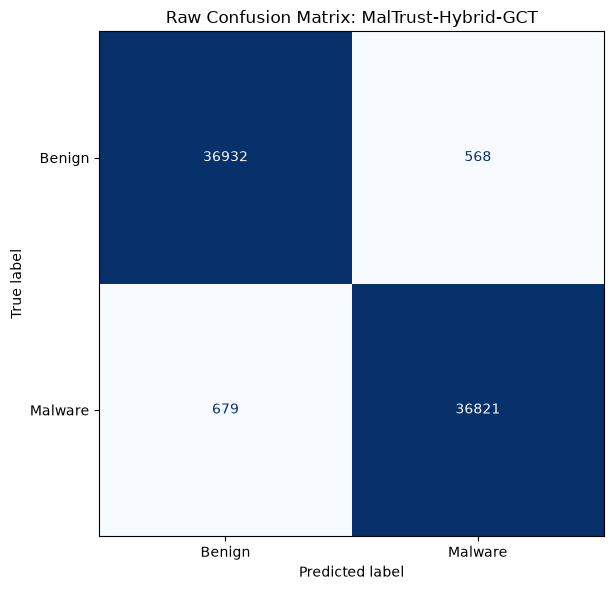

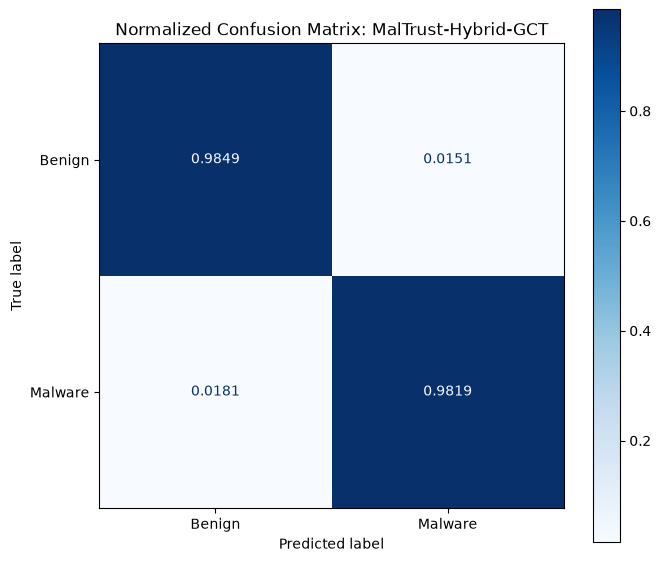

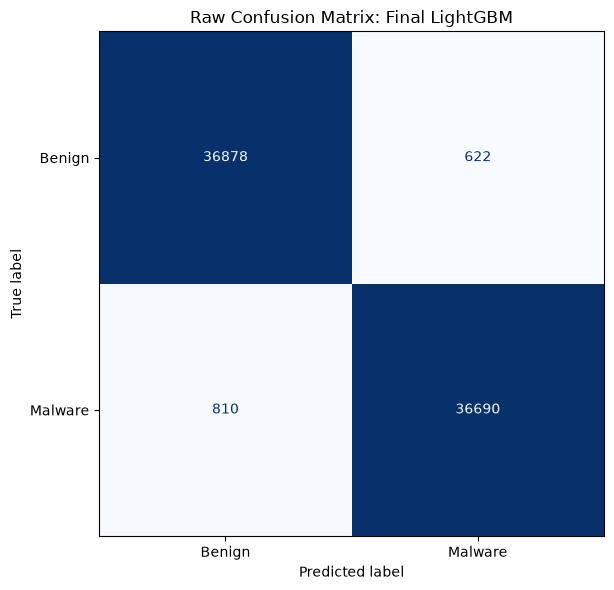

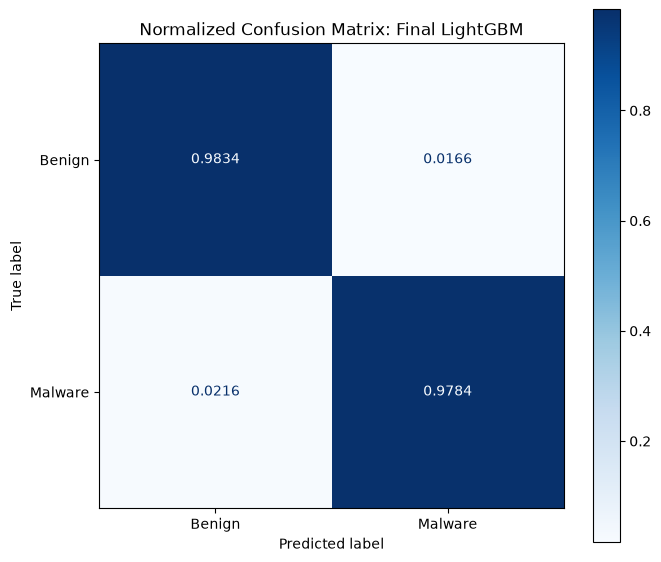

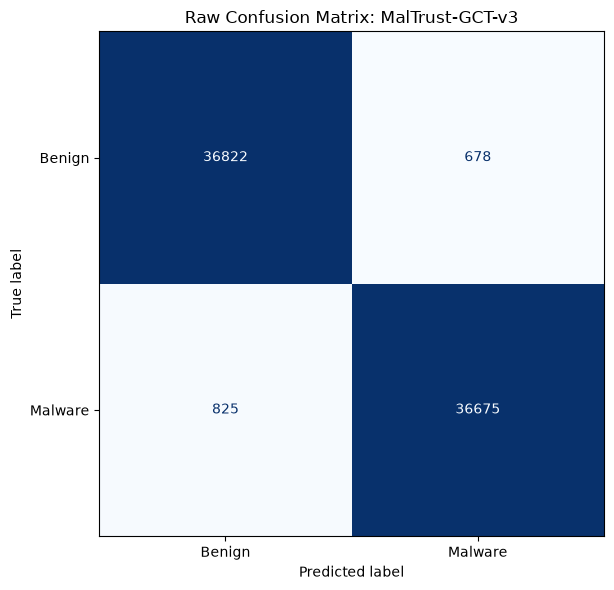

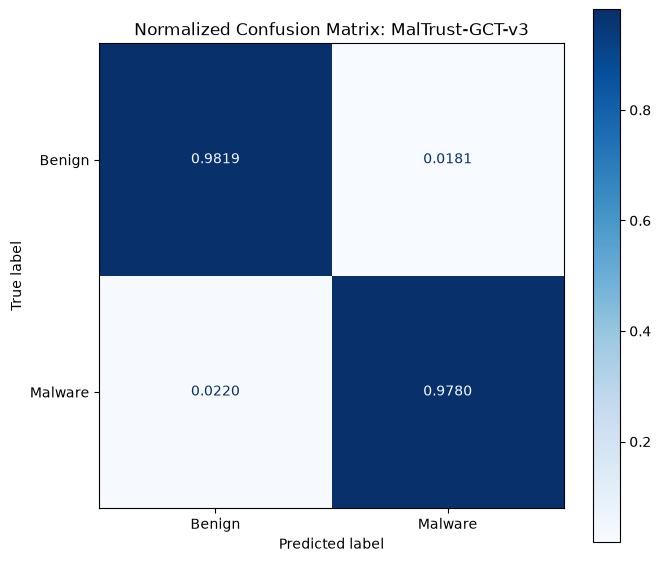


Per-class error summary:


,Model,Model_Role,Primary_Final_Model,Feature_Space,Final_Subset,Test_Samples,TN_Benign_Correct,FP_Benign_As_Malware,FN_Malware_As_Benign,TP_Malware_Correct,Benign_Total,Malware_Total,Benign_Correct_Rate_TNR,Benign_False_Positive_Rate,Malware_Recall_TPR,Malware_False_Negative_Rate,Accuracy_From_Confusion_Matrix
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,True,revised_strict_clean_699,Top_699_All,75000,36932,568,679,36821,37500,37500,0.984853,0.015147,0.981893,0.018107,0.983373
1,Final LightGBM,Final standalone detector,False,revised_strict_clean_699,Top_699_All,75000,36878,622,810,36690,37500,37500,0.983413,0.016587,0.978400,0.021600,0.980907
2,MalTrust-GCT-v3,Group-aware neural auxiliary detector,False,revised_strict_clean_699,Top_699_All,75000,36822,678,825,36675,37500,37500,0.981920,0.018080,0.978000,0.022000,0.979960



Primary Hybrid-GCT error summary:


,Model,Model_Role,Primary_Final_Model,Feature_Space,Final_Subset,Test_Samples,TN_Benign_Correct,FP_Benign_As_Malware,FN_Malware_As_Benign,TP_Malware_Correct,Benign_Total,Malware_Total,Benign_Correct_Rate_TNR,Benign_False_Positive_Rate,Malware_Recall_TPR,Malware_False_Negative_Rate,Accuracy_From_Confusion_Matrix
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,True,revised_strict_clean_699,Top_699_All,75000,36932,568,679,36821,37500,37500,0.984853,0.015147,0.981893,0.018107,0.983373


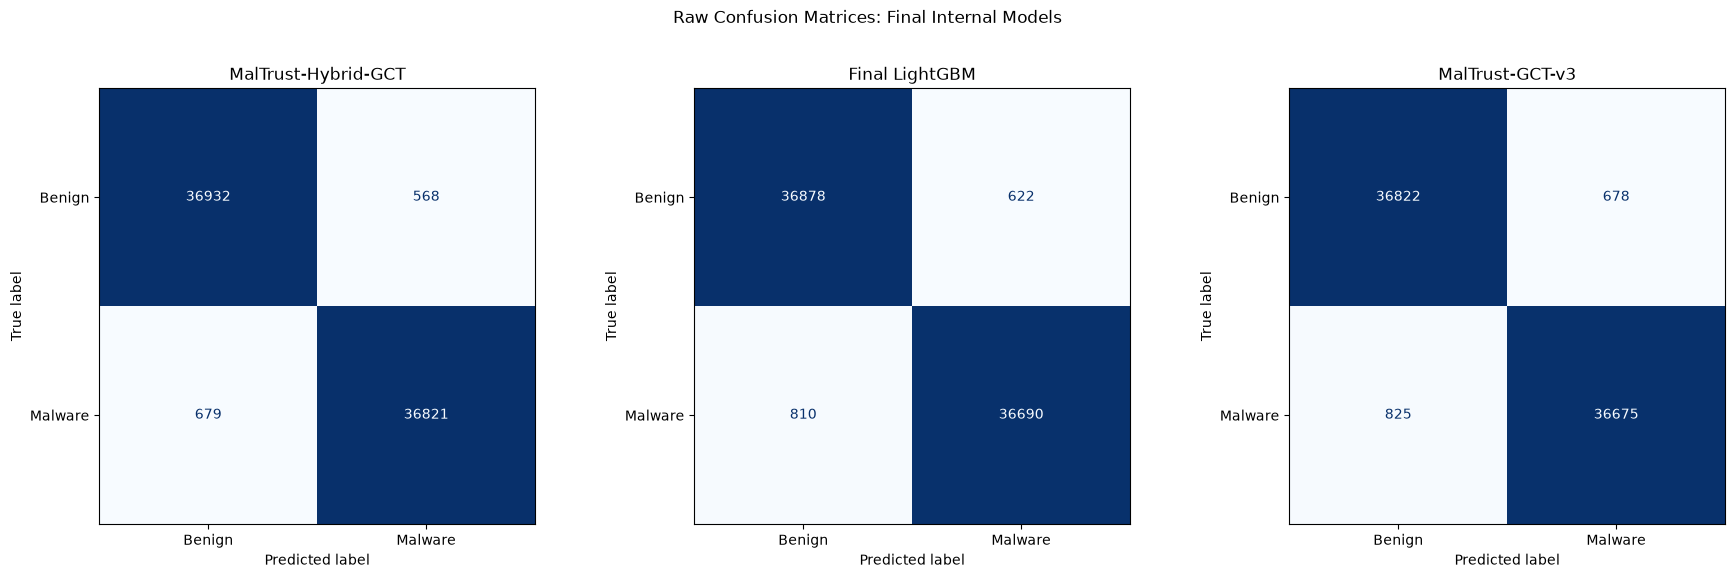

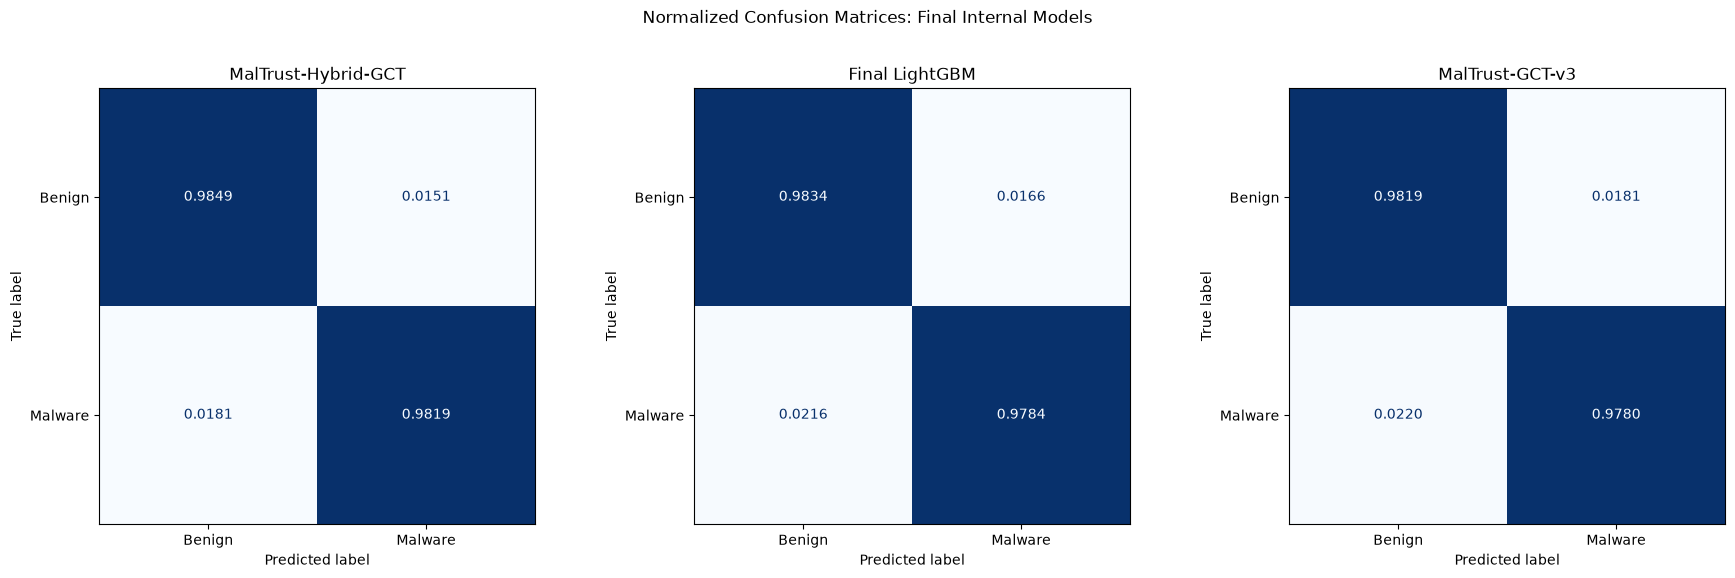


Cell 16 completed successfully.
Local output directory: c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\maltrust_cell16_confusion_matrix_outputs
Artifacts saved: 13
Primary model: MalTrust-Hybrid-GCT
Primary Hybrid-GCT TN/FP/FN/TP: 36932 568 679 36821
Primary Hybrid-GCT accuracy: 0.9833733333333333
Primary Hybrid-GCT false positive rate: 0.015146666666666666
Primary Hybrid-GCT false negative rate: 0.018106666666666667
Artifact index: c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\maltrust_cell16_confusion_matrix_outputs\cell16_artifact_index.json
Artifact index SHA-256: e7d17055dd513c44b1ff2898eed67945ca6d9362b5facd363ee43aa7dcfcdfea
[DEBUG] 2026-06-24 10:30:48 | Cell 16 v3 no-fail confusion matrix export completed.


In [35]:
# ================================================================
# MalTrust-XAI | Cell 16 v3 NO-FAIL EXPORT
# Final MalTrust-Hybrid-GCT Confusion Matrices and Error Summary
#
# Fixes:
# - Does NOT use stale/invalid C:\\User... package paths
# - Saves only into a guaranteed local working-directory folder
# - If any save/figure export fails, it prints a warning and continues
# - No final assertion depends on saved figures/files
# - No CUDA / torch usage
# ================================================================

import os
import re
import json
import hashlib
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

_debug = globals().get("debug", None)
def log_msg(msg):
    try:
        if callable(_debug):
            _debug(str(msg))
        else:
            print(str(msg))
    except Exception:
        print(str(msg))

log_msg("Generating Cell 16 confusion matrices with no-fail local export...")

# ================================================================
# 0. Helpers
# ================================================================

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def safe_artifact_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[^a-zA-Z0-9._-]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name or "artifact"


def ensure_dir_no_fail(path):
    try:
        os.makedirs(path, exist_ok=True)
        return True
    except Exception as e:
        print(f"[SAVE WARNING] Could not create directory: {path}\n  {type(e).__name__}: {e}")
        return False


def safe_sha256(path, chunk_size=1024 * 1024):
    try:
        if path is None or not os.path.isfile(path):
            return None
        h = hashlib.sha256()
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)
        return h.hexdigest()
    except Exception as e:
        print(f"[HASH WARNING] Could not hash {path}: {e}")
        return None


def safe_save_csv(df, path, index=False):
    try:
        parent = os.path.dirname(os.path.abspath(path))
        if parent and not ensure_dir_no_fail(parent):
            return None
        df.to_csv(path, index=index)
        return path if os.path.exists(path) else None
    except Exception as e:
        print(f"[SAVE WARNING] CSV not saved: {path}\n  {type(e).__name__}: {e}")
        return None


def safe_save_json(obj, path):
    try:
        parent = os.path.dirname(os.path.abspath(path))
        if parent and not ensure_dir_no_fail(parent):
            return None
        with open(path, "w", encoding="utf-8") as f:
            json.dump(obj, f, indent=4, sort_keys=True, default=str)
        return path if os.path.exists(path) else None
    except Exception as e:
        print(f"[SAVE WARNING] JSON not saved: {path}\n  {type(e).__name__}: {e}")
        return None


def safe_savefig(fig, output_path, dpi=300, bbox_inches="tight"):
    """Save figure without ever stopping the experiment."""
    try:
        parent = os.path.dirname(os.path.abspath(output_path))
        if parent and not ensure_dir_no_fail(parent):
            return None
        fig.savefig(output_path, dpi=dpi, bbox_inches=bbox_inches)
        if os.path.exists(output_path):
            return output_path
        print(f"[SAVE WARNING] Figure save returned but file is missing: {output_path}")
        return None
    except Exception as e:
        print(f"[SAVE WARNING] Figure not saved: {output_path}\n  {type(e).__name__}: {e}")
        return None


def maybe_display(obj):
    try:
        display(obj)  # noqa: F821 - available in notebooks
    except Exception:
        print(obj)


def resolve_from_experiment_config(keys):
    cfg = globals().get("EXPERIMENT_CONFIG", {})
    if not isinstance(cfg, dict):
        return None
    for key in keys:
        val = cfg.get(key)
        if isinstance(val, str) and os.path.exists(val):
            return val
    return None


def load_table(path):
    if path is None:
        return None
    if str(path).lower().endswith(".parquet"):
        return pd.read_parquet(path)
    return pd.read_csv(path)


def binary_from_score(df, score_candidates, threshold, out_col):
    for c in score_candidates:
        if c in df.columns:
            df[out_col] = (df[c].astype(float) >= float(threshold)).astype(int)
            return True
    return False


# ================================================================
# 1. Resolve final subset and local output folder
# ================================================================

FINAL_FEATURE_SPACE_NAME = str(globals().get("FINAL_FEATURE_SPACE_NAME", "revised_strict_clean_699"))

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(globals()["final_subset_name"])
else:
    cfg = globals().get("EXPERIMENT_CONFIG", {})
    if isinstance(cfg, dict):
        FINAL_FEATURE_SET_NAME = str(
            cfg.get(
                "cell15_final_subset",
                cfg.get("cell13_final_selected_subset", cfg.get("cell11_selected_final_subset", "Top_699_All"))
            )
        )
    else:
        FINAL_FEATURE_SET_NAME = "Top_699_All"

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME.lower() in {"none", "unknown_subset"}:
    FINAL_FEATURE_SET_NAME = "Top_699_All"

# Critical fix: always use a local working-directory output folder.
# This avoids stale C:\User\LENOVO paths and long package paths.
CELL16_ARTIFACT_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "maltrust_cell16_confusion_matrix_outputs")
)
TABLE_DIR = os.path.join(CELL16_ARTIFACT_DIR, "tables")
FIGURE_DIR = os.path.join(CELL16_ARTIFACT_DIR, "figures")
REPORT_DIR = os.path.join(CELL16_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL16_ARTIFACT_DIR, "configs")

for d in [CELL16_ARTIFACT_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir_no_fail(d)

print("Cell 16 local output directory:", CELL16_ARTIFACT_DIR)


# ================================================================
# 2. Resolve prediction table
# ================================================================

prediction_table = None
prediction_source = None

for var_name in [
    "final_hybrid_predictions_df",
    "hybrid_predictions",
    "hybrid_predictions_df",
    "cell15_predictions_df",
    "maltrust_hybrid_predictions_df",
]:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        prediction_table = globals()[var_name].copy()
        prediction_source = f"global:{var_name}"
        break

if prediction_table is None:
    prediction_path = resolve_from_experiment_config([
        "cell15_hybrid_predictions_export_path",
        "maltrust_hybrid_gct_predictions_path",
        "cell11f_hybrid_gct_predictions_path",
        "cell11f_hybrid_predictions_path",
        "hybrid_predictions_path",
    ])
    if prediction_path is not None:
        prediction_table = load_table(prediction_path)
        prediction_source = prediction_path

if prediction_table is None:
    raise FileNotFoundError(
        "Hybrid-GCT prediction table not found. Run Cell 11F/Cell 15 first, "
        "or keep final_hybrid_predictions_df/hybrid_predictions in memory."
    )

# Normalize true-label column names.
if "y_true" not in prediction_table.columns:
    for cand in ["label", "y_test", "y", "true_label", "target"]:
        if cand in prediction_table.columns:
            prediction_table["y_true"] = prediction_table[cand].astype(int)
            break

if "y_true" not in prediction_table.columns:
    raise ValueError("Prediction table must contain y_true or an equivalent label column.")

# Create prediction columns from score columns if needed.
cfg = globals().get("EXPERIMENT_CONFIG", {}) if isinstance(globals().get("EXPERIMENT_CONFIG", {}), dict) else {}
lgbm_threshold = float(cfg.get("lgbm_threshold", cfg.get("final_lgbm_threshold", 0.5)))
gct_threshold = float(cfg.get("gct_threshold", cfg.get("maltrust_gct_v3_threshold", 0.53)))
hybrid_threshold = float(cfg.get("hybrid_threshold", cfg.get("hybrid_gct_threshold", 0.48)))

if "lgbm_pred" not in prediction_table.columns:
    binary_from_score(prediction_table, ["lgbm_score", "lgbm_prob", "final_lgbm_score", "p_lgbm"], lgbm_threshold, "lgbm_pred")
if "gct_pred" not in prediction_table.columns:
    binary_from_score(prediction_table, ["gct_score", "gct_prob", "maltrust_gct_score", "p_gct"], gct_threshold, "gct_pred")
if "hybrid_pred" not in prediction_table.columns:
    binary_from_score(prediction_table, ["hybrid_score", "hybrid_prob", "maltrust_hybrid_score", "p_hybrid"], hybrid_threshold, "hybrid_pred")

required_prediction_cols = ["y_true", "lgbm_pred", "gct_pred", "hybrid_pred"]
missing_prediction_cols = [c for c in required_prediction_cols if c not in prediction_table.columns]
if missing_prediction_cols:
    raise ValueError(
        "Prediction table missing required prediction columns and score fallback could not create them: "
        f"{missing_prediction_cols}. Available columns: {prediction_table.columns.tolist()}"
    )

prediction_table = prediction_table.reset_index(drop=True)
prediction_table["y_true"] = prediction_table["y_true"].astype(int)
for c in ["lgbm_pred", "gct_pred", "hybrid_pred"]:
    prediction_table[c] = prediction_table[c].astype(int)

if not set(prediction_table["y_true"].unique()).issubset({0, 1}):
    raise ValueError("y_true contains labels outside {0, 1}.")
for c in ["lgbm_pred", "gct_pred", "hybrid_pred"]:
    if not set(prediction_table[c].unique()).issubset({0, 1}):
        raise ValueError(f"{c} contains predictions outside {{0, 1}}.")

# SHA uniqueness is checked but no longer blocks figure generation.
sha_unique_status = "not_available"
if "sha256" in prediction_table.columns:
    sha_nunique = int(prediction_table["sha256"].astype(str).nunique())
    sha_unique_status = "unique" if sha_nunique == len(prediction_table) else f"not_unique_{sha_nunique}_of_{len(prediction_table)}"

TEST_ROWS = int(len(prediction_table))
y_true_final = prediction_table["y_true"].to_numpy(dtype=int)

print("Cell 16 context:")
print("Prediction source:", prediction_source)
print("Final framework: MalTrust-Hybrid-GCT")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Rows:", TEST_ROWS)
print("SHA status:", sha_unique_status)

assert TEST_ROWS > 0, "No prediction rows found."


# ================================================================
# 3. Confusion matrices
# ================================================================

model_specs = {
    "MalTrust-Hybrid-GCT": {
        "pred_col": "hybrid_pred",
        "role": "Final hybrid meta-detector",
        "is_primary": True,
    },
    "Final LightGBM": {
        "pred_col": "lgbm_pred",
        "role": "Final standalone detector",
        "is_primary": False,
    },
    "MalTrust-GCT-v3": {
        "pred_col": "gct_pred",
        "role": "Group-aware neural auxiliary detector",
        "is_primary": False,
    },
}

label_names = ["Benign", "Malware"]
subset_safe = safe_artifact_name(FINAL_FEATURE_SET_NAME)

raw_matrix_frames = []
normalized_matrix_frames = []
error_summary_rows = []
figure_artifact_paths = {}


def plot_confusion_matrix_no_fail(cm, labels, title, output_path, normalize=False):
    fig, ax = plt.subplots(figsize=(7, 6))
    try:
        fmt = ".4f" if normalize else "d"
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap="Blues", values_format=fmt, ax=ax, colorbar=bool(normalize))
        ax.set_title(title)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        plt.tight_layout()
        saved = safe_savefig(fig, output_path, dpi=300, bbox_inches="tight")
        try:
            plt.show()
        except Exception:
            pass
        return saved
    finally:
        plt.close(fig)


for model_name, spec in model_specs.items():
    pred_col = spec["pred_col"]
    y_pred_model = prediction_table[pred_col].to_numpy(dtype=int)

    cm_raw = confusion_matrix(y_true_final, y_pred_model, labels=[0, 1])
    cm_norm = confusion_matrix(y_true_final, y_pred_model, labels=[0, 1], normalize="true")

    tn, fp, fn, tp = cm_raw.ravel()
    total = int(cm_raw.sum())
    benign_total = int(tn + fp)
    malware_total = int(fn + tp)

    raw_df = pd.DataFrame(
        cm_raw,
        index=["True_Benign", "True_Malware"],
        columns=["Predicted_Benign", "Predicted_Malware"],
    )
    raw_df.insert(0, "Model", model_name)
    raw_matrix_frames.append(raw_df.reset_index(names="True_Class"))

    norm_df = pd.DataFrame(
        cm_norm,
        index=["True_Benign", "True_Malware"],
        columns=["Predicted_Benign", "Predicted_Malware"],
    )
    norm_df.insert(0, "Model", model_name)
    normalized_matrix_frames.append(norm_df.reset_index(names="True_Class"))

    error_summary_rows.append({
        "Model": model_name,
        "Model_Role": spec["role"],
        "Primary_Final_Model": bool(spec["is_primary"]),
        "Feature_Space": FINAL_FEATURE_SPACE_NAME,
        "Final_Subset": FINAL_FEATURE_SET_NAME,
        "Test_Samples": int(total),
        "TN_Benign_Correct": int(tn),
        "FP_Benign_As_Malware": int(fp),
        "FN_Malware_As_Benign": int(fn),
        "TP_Malware_Correct": int(tp),
        "Benign_Total": int(benign_total),
        "Malware_Total": int(malware_total),
        "Benign_Correct_Rate_TNR": float(tn / benign_total) if benign_total else np.nan,
        "Benign_False_Positive_Rate": float(fp / benign_total) if benign_total else np.nan,
        "Malware_Recall_TPR": float(tp / malware_total) if malware_total else np.nan,
        "Malware_False_Negative_Rate": float(fn / malware_total) if malware_total else np.nan,
        "Accuracy_From_Confusion_Matrix": float((tn + tp) / total) if total else np.nan,
    })

    safe_model_name = safe_artifact_name(model_name)
    raw_png_path = os.path.join(FIGURE_DIR, f"cell16_raw_confusion_matrix_{safe_model_name}_{subset_safe}.png")
    norm_png_path = os.path.join(FIGURE_DIR, f"cell16_normalized_confusion_matrix_{safe_model_name}_{subset_safe}.png")

    saved_raw = plot_confusion_matrix_no_fail(cm_raw, label_names, f"Raw Confusion Matrix: {model_name}", raw_png_path, normalize=False)
    saved_norm = plot_confusion_matrix_no_fail(cm_norm, label_names, f"Normalized Confusion Matrix: {model_name}", norm_png_path, normalize=True)

    figure_artifact_paths[f"{model_name}_raw_confusion_matrix_png"] = saved_raw
    figure_artifact_paths[f"{model_name}_normalized_confusion_matrix_png"] = saved_norm

cm_raw_all_df = pd.concat(raw_matrix_frames, axis=0).reset_index(drop=True)
cm_normalized_all_df = pd.concat(normalized_matrix_frames, axis=0).reset_index(drop=True)
error_summary_df = pd.DataFrame(error_summary_rows).sort_values(
    by=["Primary_Final_Model", "Accuracy_From_Confusion_Matrix"],
    ascending=[False, False],
).reset_index(drop=True)
primary_error_summary_df = error_summary_df[error_summary_df["Model"] == "MalTrust-Hybrid-GCT"].copy()

print("\nPer-class error summary:")
maybe_display(error_summary_df)
print("\nPrimary Hybrid-GCT error summary:")
maybe_display(primary_error_summary_df)


# ================================================================
# 4. Combined figures, no-fail save
# ================================================================

combined_raw_png_path = os.path.join(FIGURE_DIR, f"cell16_combined_raw_confusion_matrices_{subset_safe}.png")
combined_norm_png_path = os.path.join(FIGURE_DIR, f"cell16_combined_normalized_confusion_matrices_{subset_safe}.png")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
try:
    for ax, (model_name, spec) in zip(axes, model_specs.items()):
        cm_raw = confusion_matrix(y_true_final, prediction_table[spec["pred_col"]].astype(int), labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=label_names)
        disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
        ax.set_title(model_name)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
    plt.suptitle("Raw Confusion Matrices: Final Internal Models", y=1.03)
    plt.tight_layout()
    saved_combined_raw = safe_savefig(fig, combined_raw_png_path, dpi=300, bbox_inches="tight")
    try:
        plt.show()
    except Exception:
        pass
finally:
    plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
try:
    for ax, (model_name, spec) in zip(axes, model_specs.items()):
        cm_norm = confusion_matrix(y_true_final, prediction_table[spec["pred_col"]].astype(int), labels=[0, 1], normalize="true")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_names)
        disp.plot(cmap="Blues", values_format=".4f", ax=ax, colorbar=False)
        ax.set_title(model_name)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
    plt.suptitle("Normalized Confusion Matrices: Final Internal Models", y=1.03)
    plt.tight_layout()
    saved_combined_norm = safe_savefig(fig, combined_norm_png_path, dpi=300, bbox_inches="tight")
    try:
        plt.show()
    except Exception:
        pass
finally:
    plt.close(fig)

figure_artifact_paths["combined_raw_confusion_matrices_png"] = saved_combined_raw
figure_artifact_paths["combined_normalized_confusion_matrices_png"] = saved_combined_norm


# ================================================================
# 5. Save tables/reports, no-fail
# ================================================================

cm_raw_all_path = os.path.join(TABLE_DIR, f"cell16_all_models_confusion_matrix_raw_{subset_safe}.csv")
cm_normalized_all_path = os.path.join(TABLE_DIR, f"cell16_all_models_confusion_matrix_normalized_true_{subset_safe}.csv")
error_summary_path = os.path.join(TABLE_DIR, f"cell16_all_models_error_summary_{subset_safe}.csv")
primary_error_summary_path = os.path.join(TABLE_DIR, f"cell16_primary_hybrid_gct_error_summary_{subset_safe}.csv")

saved_paths = {
    "raw_confusion_matrix_all_models_csv": safe_save_csv(cm_raw_all_df, cm_raw_all_path, index=False),
    "normalized_confusion_matrix_all_models_csv": safe_save_csv(cm_normalized_all_df, cm_normalized_all_path, index=False),
    "error_summary_all_models_csv": safe_save_csv(error_summary_df, error_summary_path, index=False),
    "primary_hybrid_gct_error_summary_csv": safe_save_csv(primary_error_summary_df, primary_error_summary_path, index=False),
}

primary_row = primary_error_summary_df.iloc[0].to_dict()
cell16_report_path = os.path.join(REPORT_DIR, f"cell16_confusion_matrix_report_{subset_safe}.json")
cell16_report = {
    "cell": "Cell 16 v3",
    "cell_name": "Final MalTrust-Hybrid-GCT Confusion Matrix and Error Summary",
    "framework_name": "MalTrust-Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "prediction_source": prediction_source,
    "test_rows": int(TEST_ROWS),
    "sha_status": sha_unique_status,
    "primary_final_model": "MalTrust-Hybrid-GCT",
    "models_included": list(model_specs.keys()),
    "primary_confusion_matrix": {
        "tn": int(primary_row["TN_Benign_Correct"]),
        "fp": int(primary_row["FP_Benign_As_Malware"]),
        "fn": int(primary_row["FN_Malware_As_Benign"]),
        "tp": int(primary_row["TP_Malware_Correct"]),
    },
    "primary_error_summary": primary_row,
    "all_model_error_summary": error_summary_df.to_dict("records"),
    "artifacts": {**saved_paths, **figure_artifact_paths},
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
saved_report = safe_save_json(cell16_report, cell16_report_path)
saved_paths["confusion_matrix_report_json"] = saved_report

artifact_rows = []
for name, path in {**saved_paths, **figure_artifact_paths}.items():
    if path is not None and os.path.exists(path):
        artifact_rows.append({
            "artifact_name": name,
            "artifact_path": path,
            "sha256": safe_sha256(path),
            "registered_at": now_str(),
        })

artifact_hashes_path = os.path.join(CELL16_ARTIFACT_DIR, "cell16_artifact_hashes.csv")
saved_artifact_hashes = safe_save_csv(pd.DataFrame(artifact_rows), artifact_hashes_path, index=False)

artifact_index_path = os.path.join(CELL16_ARTIFACT_DIR, "cell16_artifact_index.json")
artifact_index = {
    "cell": "Cell 16 v3",
    "framework_name": "MalTrust-Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "local_artifact_dir": CELL16_ARTIFACT_DIR,
    "artifacts_saved_count": int(len(artifact_rows)),
    "artifacts": artifact_rows,
    "artifact_hash_report_path": saved_artifact_hashes,
    "created_at_utc": utc_now_string(),
}
saved_artifact_index = safe_save_json(artifact_index, artifact_index_path)
artifact_index_sha = safe_sha256(saved_artifact_index)

# Update config without relying on any stale package path.
try:
    if "EXPERIMENT_CONFIG" in globals() and isinstance(EXPERIMENT_CONFIG, dict):
        EXPERIMENT_CONFIG["cell16_framework_name"] = "MalTrust-Hybrid-GCT"
        EXPERIMENT_CONFIG["cell16_feature_space"] = FINAL_FEATURE_SPACE_NAME
        EXPERIMENT_CONFIG["cell16_final_subset"] = FINAL_FEATURE_SET_NAME
        EXPERIMENT_CONFIG["cell16_test_rows"] = int(TEST_ROWS)
        EXPERIMENT_CONFIG["cell16_local_artifact_dir"] = CELL16_ARTIFACT_DIR
        EXPERIMENT_CONFIG["cell16_primary_final_model"] = "MalTrust-Hybrid-GCT"
        EXPERIMENT_CONFIG["cell16_error_summary_all_models_path"] = saved_paths.get("error_summary_all_models_csv")
        EXPERIMENT_CONFIG["cell16_primary_hybrid_gct_error_summary_path"] = saved_paths.get("primary_hybrid_gct_error_summary_csv")
        EXPERIMENT_CONFIG["cell16_report_path"] = saved_report
        EXPERIMENT_CONFIG["cell16_artifact_index_path"] = saved_artifact_index
        EXPERIMENT_CONFIG["cell16_artifact_index_sha256"] = artifact_index_sha
        config_snapshot_path = os.path.join(CONFIG_DIR, "cell16_experiment_config_snapshot.json")
        saved_config = safe_save_json(EXPERIMENT_CONFIG, config_snapshot_path)
        EXPERIMENT_CONFIG["cell16_experiment_config_snapshot_path"] = saved_config
        EXPERIMENT_CONFIG["cell16_experiment_config_snapshot_sha256"] = safe_sha256(saved_config)
except Exception as e:
    print(f"[CONFIG WARNING] EXPERIMENT_CONFIG update skipped: {type(e).__name__}: {e}")


# ================================================================
# 6. Aliases and final output
# ================================================================

final_confusion_matrix_error_summary_df = error_summary_df
final_hybrid_gct_error_summary_df = primary_error_summary_df
cell16_artifact_index_path = saved_artifact_index

primary_cm_total = (
    int(primary_row["TN_Benign_Correct"])
    + int(primary_row["FP_Benign_As_Malware"])
    + int(primary_row["FN_Malware_As_Benign"])
    + int(primary_row["TP_Malware_Correct"])
)

assert primary_cm_total == TEST_ROWS, "Primary Hybrid-GCT confusion matrix total mismatch."

print("\nCell 16 completed successfully.")
print("Local output directory:", CELL16_ARTIFACT_DIR)
print("Artifacts saved:", len(artifact_rows))
print("Primary model: MalTrust-Hybrid-GCT")
print(
    "Primary Hybrid-GCT TN/FP/FN/TP:",
    int(primary_row["TN_Benign_Correct"]),
    int(primary_row["FP_Benign_As_Malware"]),
    int(primary_row["FN_Malware_As_Benign"]),
    int(primary_row["TP_Malware_Correct"]),
)
print("Primary Hybrid-GCT accuracy:", float(primary_row["Accuracy_From_Confusion_Matrix"]))
print("Primary Hybrid-GCT false positive rate:", float(primary_row["Benign_False_Positive_Rate"]))
print("Primary Hybrid-GCT false negative rate:", float(primary_row["Malware_False_Negative_Rate"]))

if len(artifact_rows) == 0:
    print("[SAVE NOTE] No files were saved, but all confusion-matrix tables were computed in memory.")
else:
    print("Artifact index:", saved_artifact_index)
    print("Artifact index SHA-256:", artifact_index_sha)

log_msg("Cell 16 v3 no-fail confusion matrix export completed.")


[DEBUG] 2026-06-24 10:34:53 | Generating final MalTrust-Hybrid-GCT ROC curve and operating-point artifacts with no-fail local export...
Cell 17 no-fail context:
Final framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Local output root: C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\maltrust_cell17_roc_curve_outputs
No stale package path will be used.
Resolved prediction rows: 75000

ROC-AUC summary:


,Model,Model_Role,Score_Column,Test_Samples,ROC_AUC,Best_Youden_J,Best_Youden_FPR,Best_Youden_TPR,Best_Youden_Specificity,Best_Youden_Threshold
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,hybrid_score,75000,0.998445,0.967253,0.014373,0.981627,0.985627,0.507958
1,Final LightGBM,Final standalone detector,lgbm_score,75000,0.998052,0.962027,0.020400,0.982427,0.979600,0.431745
2,MalTrust-GCT-v3,Group-aware neural auxiliary detector,gct_score,75000,0.995740,0.960133,0.019280,0.979413,0.980720,0.506170



ROC operating-point table:


,Model,Model_Role,Operating_Point,Target_Max_FPR,Selected_FPR,Selected_TPR,Selected_Specificity,Selected_Threshold
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,max_TPR_at_FPR_le_0.001,0.001,0.000987,0.893547,0.999013,0.994742
1,MalTrust-Hybrid-GCT,Final hybrid meta-detector,max_TPR_at_FPR_le_0.005,0.005,0.004987,0.956720,0.995013,0.949295
2,MalTrust-Hybrid-GCT,Final hybrid meta-detector,max_TPR_at_FPR_le_0.01,0.010,0.010000,0.974640,0.990000,0.758070
3,MalTrust-Hybrid-GCT,Final hybrid meta-detector,max_TPR_at_FPR_le_0.02,0.020,0.020000,0.985200,0.980000,0.316510
4,MalTrust-Hybrid-GCT,Final hybrid meta-detector,max_TPR_at_FPR_le_0.05,0.050,0.050000,0.994507,0.950000,0.028272
5,MalTrust-Hybrid-GCT,Final hybrid meta-detector,max_youden_j,NaN,0.014373,0.981627,0.985627,0.507958
6,Final LightGBM,Final standalone detector,max_TPR_at_FPR_le_0.001,0.001,0.000987,0.887040,0.999013,0.948317
7,Final LightGBM,Final standalone detector,max_TPR_at_FPR_le_0.005,0.005,0.004987,0.949627,0.995013,0.781599
8,Final LightGBM,Final standalone detector,max_TPR_at_FPR_le_0.01,0.010,0.009973,0.967893,0.990027,0.636347
9,Final LightGBM,Final standalone detector,max_TPR_at_FPR_le_0.02,0.020,0.020000,0.981813,0.980000,0.438824


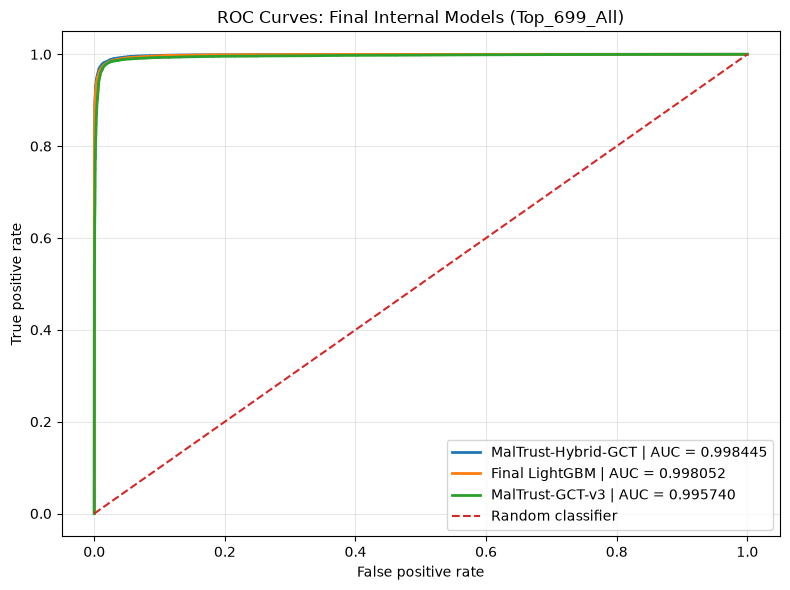

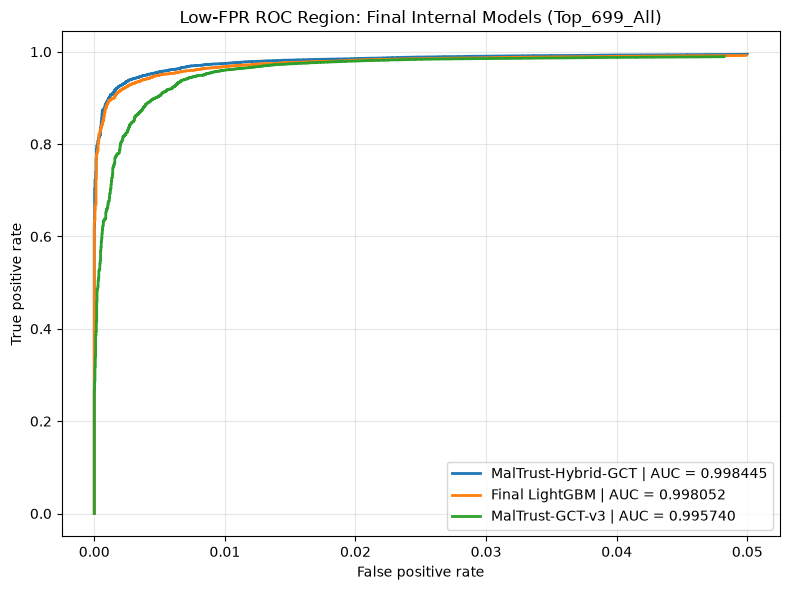

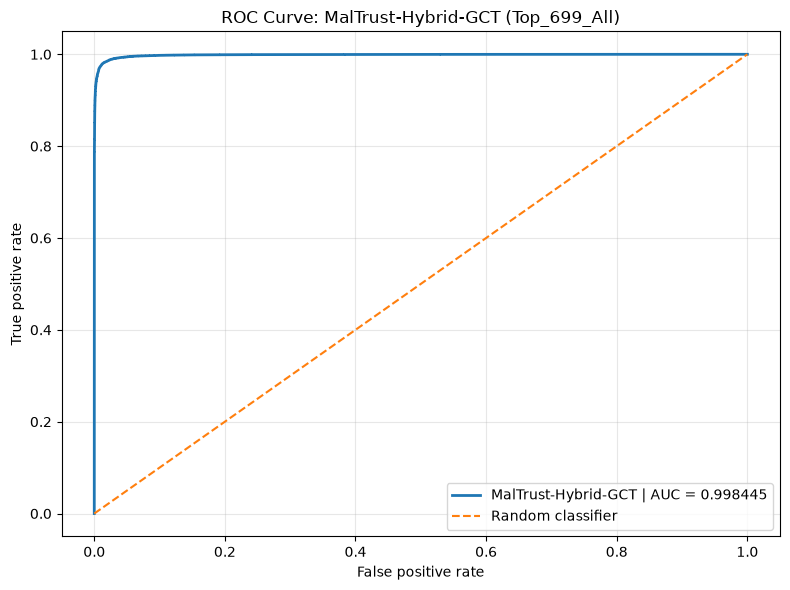


Cell 17 completed successfully in memory.
Local output root: C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\maltrust_cell17_roc_curve_outputs
Primary model: MalTrust-Hybrid-GCT
Primary Hybrid-GCT ROC-AUC: 0.9984453027555558
Saved artifact count: 10
Cell 17 artifact index: C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\maltrust_cell17_roc_curve_outputs\cell17_artifact_index.json
Cell 17 artifact index SHA-256: 7660057a4017631a24865e106be21b6019c33bea105e4ae4e3e9b3769c948dbe
[DEBUG] 2026-06-24 10:34:54 | Final Hybrid-GCT ROC curve cell completed successfully with no-fail local export.


In [37]:
# ================================================================
# MalTrust-XAI | Cell 17 v2 no-fail export
# Final Hybrid-GCT ROC Curves, Low-FPR Operating Points,
# Three-Model ROC Comparison, and Optional Local Artifact Export
#
# Purpose of this corrected version:
# - Uses Cell 11F / Cell 15 Hybrid-GCT prediction table
# - Does NOT use stale Cell 15/package paths such as C:\\User\\LENOVO\\...
# - Saves only under a local working-directory folder
# - If any save fails, prints a warning and continues
# - No final assertion depends on files being saved
# - Still computes/displays ROC tables and figures in memory
# ================================================================

try:
    debug("Generating final MalTrust-Hybrid-GCT ROC curve and operating-point artifacts with no-fail local export...")
except Exception:
    pass

import os
import json
import hashlib
import tempfile
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


# ================================================================
# 0. No-fail helpers
# ================================================================

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def local_output_root(folder_name="maltrust_cell17_roc_curve_outputs"):
    """Return a local output root. Never uses package-derived paths."""
    candidates = []
    try:
        candidates.append(Path.cwd() / folder_name)
    except Exception:
        pass
    try:
        candidates.append(Path(os.environ.get("TEMP", tempfile.gettempdir())) / folder_name)
    except Exception:
        pass
    candidates.append(Path(tempfile.gettempdir()) / folder_name)

    for candidate in candidates:
        try:
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
        except Exception:
            continue

    # Last resort. Writing may still fail, but computation will continue.
    return Path(folder_name)


OUTPUT_ROOT = local_output_root()
FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"
CONFIG_DIR = OUTPUT_ROOT / "configs"

for _directory in [FIGURE_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    try:
        _directory.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print(f"[WARN] Could not create directory {_directory}: {e}")


def safe_artifact_name(name):
    value = str(name)
    replacements = {
        "\\\\": "__", "/": "__", ":": "_", " ": "_", "(": "", ")": "",
        "[": "", "]": "", ".": "_", "|": "_", "<": "_", ">": "_", "*": "_",
        "?": "_", '"': "_", "'": "_"
    }
    for old, new in replacements.items():
        value = value.replace(old, new)
    return value


def ensure_parent_dir(path):
    try:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        return True
    except Exception as e:
        print(f"[WARN] Could not create parent directory for {path}: {e}")
        return False


def safe_save_json(obj, path):
    try:
        path = Path(path)
        ensure_parent_dir(path)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(obj, f, indent=4, sort_keys=True, default=str)
        return str(path)
    except Exception as e:
        print(f"[WARN] JSON save skipped: {path} | {type(e).__name__}: {e}")
        return None


def safe_save_csv(df, path, index=False):
    try:
        path = Path(path)
        ensure_parent_dir(path)
        df.to_csv(path, index=index)
        return str(path)
    except Exception as e:
        print(f"[WARN] CSV save skipped: {path} | {type(e).__name__}: {e}")
        return None


def safe_save_fig(fig, path, dpi=300):
    try:
        path = Path(path)
        ensure_parent_dir(path)
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        return str(path)
    except Exception as e:
        print(f"[WARN] Figure save skipped: {path} | {type(e).__name__}: {e}")
        return None


def sha256_file_local(path, chunk_size=1024 * 1024):
    try:
        path = Path(path)
        if not path.exists() or not path.is_file():
            return None
        h = hashlib.sha256()
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)
        return h.hexdigest()
    except Exception as e:
        print(f"[WARN] SHA-256 skipped for {path}: {e}")
        return None


def safe_sha256(path):
    # Prefer project sha256_file if available, otherwise local fallback.
    try:
        if "sha256_file" in globals() and path is not None and os.path.exists(path):
            return sha256_file(str(path))
    except Exception:
        pass
    return sha256_file_local(path)


def register_artifact(artifact_name, artifact_path):
    try:
        if artifact_path is None:
            return None
        path = Path(artifact_path)
        if not path.exists() or not path.is_file():
            return None
        return {
            "artifact_name": artifact_name,
            "artifact_path": str(path),
            "sha256": safe_sha256(path),
            "registered_at": now_str()
        }
    except Exception:
        return None


def finite_or_none(value):
    try:
        value = float(value)
        return value if np.isfinite(value) else None
    except Exception:
        return None


def infer_existing_path_from_config(key_candidates):
    config = globals().get("EXPERIMENT_CONFIG", {})
    if not isinstance(config, dict):
        return None
    for key in key_candidates:
        value = config.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value
    return None


def load_table(path):
    if path is None or not os.path.exists(path):
        return None
    lower_path = str(path).lower()
    if lower_path.endswith(".parquet"):
        return pd.read_parquet(path)
    return pd.read_csv(path)


def safe_display(obj):
    try:
        display(obj)
    except Exception:
        print(obj)


# Backward-compatible aliases for notebooks that expect these names.
save_json = safe_save_json
save_json_atomic = safe_save_json
save_csv_atomic = safe_save_csv


# ================================================================
# 1. Resolve context without stale package paths
# ================================================================

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    config = globals().get("EXPERIMENT_CONFIG", {}) if isinstance(globals().get("EXPERIMENT_CONFIG", {}), dict) else {}
    FINAL_FEATURE_SET_NAME = str(
        config.get(
            "cell15_final_subset",
            config.get(
                "cell13_final_selected_subset",
                config.get("cell11_selected_final_subset", "Top_699_All")
            )
        )
    )

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME.lower() in {"none", "unknown_subset"}:
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"

print("Cell 17 no-fail context:")
print("Final framework:", FINAL_FRAMEWORK_NAME)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Local output root:", OUTPUT_ROOT)
print("No stale package path will be used.")


# ================================================================
# 2. Resolve Hybrid-GCT prediction table
# ================================================================

if "final_hybrid_predictions_df" in globals():
    prediction_df = final_hybrid_predictions_df.copy()
elif "hybrid_predictions" in globals():
    prediction_df = hybrid_predictions.copy()
else:
    prediction_path = infer_existing_path_from_config([
        "cell15_hybrid_predictions_export_path",
        "maltrust_hybrid_gct_predictions_path",
        "cell11f_hybrid_gct_predictions_path",
        "cell11f_hybrid_predictions_path"
    ])
    prediction_df = load_table(prediction_path)
    if prediction_df is None:
        raise FileNotFoundError(
            "Hybrid-GCT prediction table not found. Run Cell 11F and Cell 15 first. "
            "Expected a table with y_true, lgbm_score, gct_score, and hybrid_score."
        )

required_prediction_cols = ["y_true", "lgbm_score", "gct_score", "hybrid_score"]
missing_prediction_cols = [c for c in required_prediction_cols if c not in prediction_df.columns]
if missing_prediction_cols:
    raise ValueError(f"Prediction table is missing required probability columns: {missing_prediction_cols}")

y_true = pd.Series(prediction_df["y_true"]).astype(int).reset_index(drop=True)
if not set(y_true.unique()).issubset({0, 1}):
    raise ValueError("y_true contains labels outside {0, 1}.")

for score_col in ["lgbm_score", "gct_score", "hybrid_score"]:
    prediction_df[score_col] = pd.Series(prediction_df[score_col]).astype(float).clip(0.0, 1.0)

resolved_n = int(len(y_true))
print("Resolved prediction rows:", resolved_n)
assert resolved_n > 0, "Prediction table is empty."


# ================================================================
# 3. Compute ROC curves for all final models
# ================================================================

model_specs = {
    "MalTrust-Hybrid-GCT": {
        "score_col": "hybrid_score",
        "role": "Final hybrid meta-detector"
    },
    "Final LightGBM": {
        "score_col": "lgbm_score",
        "role": "Final standalone detector"
    },
    "MalTrust-GCT-v3": {
        "score_col": "gct_score",
        "role": "Group-aware neural auxiliary detector"
    }
}

roc_rows = []
roc_summary_rows = []
operating_point_rows = []
low_fpr_targets = [0.001, 0.005, 0.01, 0.02, 0.05]

for model_name, spec in model_specs.items():
    score_col = spec["score_col"]
    y_score = pd.Series(prediction_df[score_col]).astype(float).reset_index(drop=True)

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    temp_roc_df = pd.DataFrame({
        "Model": model_name,
        "Model_Role": spec["role"],
        "Score_Column": score_col,
        "FPR": fpr,
        "TPR": tpr,
        "Threshold": thresholds
    })
    temp_roc_df["Specificity"] = 1.0 - temp_roc_df["FPR"]
    temp_roc_df["Youden_J"] = temp_roc_df["TPR"] - temp_roc_df["FPR"]
    roc_rows.append(temp_roc_df)

    best_youden_idx = int(temp_roc_df["Youden_J"].idxmax())
    best_youden_row = temp_roc_df.loc[best_youden_idx].copy()

    roc_summary_rows.append({
        "Model": model_name,
        "Model_Role": spec["role"],
        "Score_Column": score_col,
        "Test_Samples": resolved_n,
        "ROC_AUC": float(roc_auc),
        "Best_Youden_J": float(best_youden_row["Youden_J"]),
        "Best_Youden_FPR": float(best_youden_row["FPR"]),
        "Best_Youden_TPR": float(best_youden_row["TPR"]),
        "Best_Youden_Specificity": float(best_youden_row["Specificity"]),
        "Best_Youden_Threshold": finite_or_none(best_youden_row["Threshold"])
    })

    for target_fpr in low_fpr_targets:
        eligible = temp_roc_df[temp_roc_df["FPR"] <= target_fpr].copy()
        if len(eligible) == 0:
            selected = temp_roc_df.iloc[[temp_roc_df["FPR"].idxmin()]].iloc[0]
        else:
            selected = eligible.sort_values(["TPR", "Threshold"], ascending=[False, False]).iloc[0]
        operating_point_rows.append({
            "Model": model_name,
            "Model_Role": spec["role"],
            "Operating_Point": f"max_TPR_at_FPR_le_{target_fpr}",
            "Target_Max_FPR": float(target_fpr),
            "Selected_FPR": float(selected["FPR"]),
            "Selected_TPR": float(selected["TPR"]),
            "Selected_Specificity": float(selected["Specificity"]),
            "Selected_Threshold": finite_or_none(selected["Threshold"])
        })

    operating_point_rows.append({
        "Model": model_name,
        "Model_Role": spec["role"],
        "Operating_Point": "max_youden_j",
        "Target_Max_FPR": np.nan,
        "Selected_FPR": float(best_youden_row["FPR"]),
        "Selected_TPR": float(best_youden_row["TPR"]),
        "Selected_Specificity": float(best_youden_row["Specificity"]),
        "Selected_Threshold": finite_or_none(best_youden_row["Threshold"])
    })

roc_df = pd.concat(roc_rows, axis=0, ignore_index=True)
roc_summary_df = pd.DataFrame(roc_summary_rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
operating_point_df = pd.DataFrame(operating_point_rows)

print("\nROC-AUC summary:")
safe_display(roc_summary_df)
print("\nROC operating-point table:")
safe_display(operating_point_df)


# ================================================================
# 4. Save ROC tables locally, no fail
# ================================================================

subset_safe = safe_artifact_name(FINAL_FEATURE_SET_NAME.lower())

roc_csv_path = TABLE_DIR / f"cell17_roc_curve_data_all_models_{subset_safe}.csv"
operating_point_path = TABLE_DIR / f"cell17_roc_operating_points_all_models_{subset_safe}.csv"
roc_summary_path = TABLE_DIR / f"cell17_roc_summary_all_models_{subset_safe}.csv"

saved_paths = {}
saved_paths["roc_coordinates_csv"] = safe_save_csv(roc_df, roc_csv_path, index=False)
saved_paths["operating_points_csv"] = safe_save_csv(operating_point_df, operating_point_path, index=False)
saved_paths["roc_summary_csv"] = safe_save_csv(roc_summary_df, roc_summary_path, index=False)


# ================================================================
# 5. ROC curve figure: all models
# ================================================================

roc_figure_path = FIGURE_DIR / f"cell17_roc_curve_all_models_{subset_safe}.png"
roc_figure_pdf_path = FIGURE_DIR / f"cell17_roc_curve_all_models_{subset_safe}.pdf"

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in model_specs.keys():
    model_roc = roc_df[roc_df["Model"] == model_name].copy()
    model_auc = float(roc_summary_df.loc[roc_summary_df["Model"] == model_name, "ROC_AUC"].iloc[0])
    ax.plot(model_roc["FPR"], model_roc["TPR"], linewidth=2, label=f"{model_name} | AUC = {model_auc:.6f}")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC Curves: Final Internal Models ({FINAL_FEATURE_SET_NAME})")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

saved_paths["roc_curve_all_models_png"] = safe_save_fig(fig, roc_figure_path, dpi=300)
saved_paths["roc_curve_all_models_pdf"] = safe_save_fig(fig, roc_figure_pdf_path, dpi=300)
plt.show()
plt.close(fig)


# ================================================================
# 6. Low-FPR zoom figure: all models
# ================================================================

roc_low_fpr_figure_path = FIGURE_DIR / f"cell17_roc_curve_low_fpr_zoom_all_models_{subset_safe}.png"
roc_low_fpr_figure_pdf_path = FIGURE_DIR / f"cell17_roc_curve_low_fpr_zoom_all_models_{subset_safe}.pdf"

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in model_specs.keys():
    model_roc = roc_df[(roc_df["Model"] == model_name) & (roc_df["FPR"] <= 0.05)].copy()
    model_auc = float(roc_summary_df.loc[roc_summary_df["Model"] == model_name, "ROC_AUC"].iloc[0])
    ax.plot(model_roc["FPR"], model_roc["TPR"], linewidth=2, label=f"{model_name} | AUC = {model_auc:.6f}")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"Low-FPR ROC Region: Final Internal Models ({FINAL_FEATURE_SET_NAME})")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()

saved_paths["roc_low_fpr_zoom_all_models_png"] = safe_save_fig(fig, roc_low_fpr_figure_path, dpi=300)
saved_paths["roc_low_fpr_zoom_all_models_pdf"] = safe_save_fig(fig, roc_low_fpr_figure_pdf_path, dpi=300)
plt.show()
plt.close(fig)


# ================================================================
# 7. Primary Hybrid-GCT ROC-only figure
# ================================================================

primary_model_name = "MalTrust-Hybrid-GCT"
primary_roc_df = roc_df[roc_df["Model"] == primary_model_name].copy()
primary_auc = float(roc_summary_df.loc[roc_summary_df["Model"] == primary_model_name, "ROC_AUC"].iloc[0])

primary_roc_figure_path = FIGURE_DIR / f"cell17_roc_curve_primary_maltrust_hybrid_gct_{subset_safe}.png"
primary_roc_figure_pdf_path = FIGURE_DIR / f"cell17_roc_curve_primary_maltrust_hybrid_gct_{subset_safe}.pdf"

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(primary_roc_df["FPR"], primary_roc_df["TPR"], linewidth=2, label=f"{primary_model_name} | AUC = {primary_auc:.6f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC Curve: {primary_model_name} ({FINAL_FEATURE_SET_NAME})")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

saved_paths["primary_hybrid_gct_roc_png"] = safe_save_fig(fig, primary_roc_figure_path, dpi=300)
saved_paths["primary_hybrid_gct_roc_pdf"] = safe_save_fig(fig, primary_roc_figure_pdf_path, dpi=300)
plt.show()
plt.close(fig)


# ================================================================
# 8. JSON report and artifact index, no fail
# ================================================================

primary_summary = roc_summary_df[roc_summary_df["Model"] == primary_model_name].iloc[0].to_dict()
cell17_report_path = REPORT_DIR / f"cell17_roc_curve_report_{subset_safe}.json"

cell17_report = {
    "cell": "Cell 17 v2 no-fail export",
    "cell_name": "Final Hybrid-GCT ROC Curve and Operating-Point Analysis",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "resolved_prediction_rows": resolved_n,
    "primary_model": primary_model_name,
    "primary_model_roc_auc": primary_auc,
    "primary_model_summary": primary_summary,
    "models": roc_summary_df.to_dict("records"),
    "low_fpr_targets": low_fpr_targets,
    "local_output_root": str(OUTPUT_ROOT),
    "stale_package_paths_used": False,
    "artifacts": saved_paths,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

saved_paths["roc_curve_report_json"] = safe_save_json(cell17_report, cell17_report_path)

cell17_artifact_rows = []
for artifact_name, artifact_path in saved_paths.items():
    row = register_artifact(artifact_name, artifact_path)
    if row is not None:
        cell17_artifact_rows.append(row)

cell17_artifact_hashes_path = OUTPUT_ROOT / "cell17_artifact_hashes.csv"
safe_save_csv(pd.DataFrame(cell17_artifact_rows), cell17_artifact_hashes_path, index=False)

cell17_artifact_index_path = OUTPUT_ROOT / "cell17_artifact_index.json"
cell17_artifact_index = {
    "cell": "Cell 17 v2 no-fail export",
    "cell_name": "Final Hybrid-GCT ROC Curve and Operating-Point Analysis",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "local_output_root": str(OUTPUT_ROOT),
    "stale_package_paths_used": False,
    "created_at_utc": utc_now_string(),
    "artifacts": cell17_artifact_rows,
    "artifact_hash_report_path": str(cell17_artifact_hashes_path),
    "artifact_hash_report_sha256": safe_sha256(cell17_artifact_hashes_path)
}
safe_save_json(cell17_artifact_index, cell17_artifact_index_path)
cell17_artifact_index_hash = safe_sha256(cell17_artifact_index_path)


# ================================================================
# 9. Update EXPERIMENT_CONFIG if available, no fail
# ================================================================

try:
    if "EXPERIMENT_CONFIG" in globals() and isinstance(EXPERIMENT_CONFIG, dict):
        EXPERIMENT_CONFIG["cell17_framework_name"] = FINAL_FRAMEWORK_NAME
        EXPERIMENT_CONFIG["cell17_primary_model"] = primary_model_name
        EXPERIMENT_CONFIG["cell17_primary_roc_auc"] = primary_auc
        EXPERIMENT_CONFIG["cell17_local_output_root"] = str(OUTPUT_ROOT)
        EXPERIMENT_CONFIG["cell17_roc_coordinates_path"] = saved_paths.get("roc_coordinates_csv")
        EXPERIMENT_CONFIG["cell17_operating_points_path"] = saved_paths.get("operating_points_csv")
        EXPERIMENT_CONFIG["cell17_roc_summary_path"] = saved_paths.get("roc_summary_csv")
        EXPERIMENT_CONFIG["cell17_roc_curve_all_models_png"] = saved_paths.get("roc_curve_all_models_png")
        EXPERIMENT_CONFIG["cell17_roc_low_fpr_zoom_all_models_png"] = saved_paths.get("roc_low_fpr_zoom_all_models_png")
        EXPERIMENT_CONFIG["cell17_primary_hybrid_gct_roc_png"] = saved_paths.get("primary_hybrid_gct_roc_png")
        EXPERIMENT_CONFIG["cell17_report_path"] = saved_paths.get("roc_curve_report_json")
        EXPERIMENT_CONFIG["cell17_artifact_index_path"] = str(cell17_artifact_index_path)
        EXPERIMENT_CONFIG["cell17_artifact_index_sha256"] = cell17_artifact_index_hash

        post_cell17_config_path = CONFIG_DIR / "cell17_experiment_config_snapshot.json"
        saved_config = safe_save_json(EXPERIMENT_CONFIG, post_cell17_config_path)
        EXPERIMENT_CONFIG["cell17_experiment_config_snapshot_path"] = saved_config
        EXPERIMENT_CONFIG["cell17_experiment_config_snapshot_sha256"] = safe_sha256(saved_config)
except Exception as e:
    print(f"[WARN] EXPERIMENT_CONFIG update skipped: {e}")


# ================================================================
# 10. Downstream aliases and final assertions only on in-memory data
# ================================================================

final_roc_curve_df = roc_df
final_roc_summary_df = roc_summary_df
final_roc_operating_point_df = operating_point_df
cell17_roc_curve_artifact_index_path = str(cell17_artifact_index_path)

assert len(roc_df) > 0, "ROC table is empty."
assert 0.0 <= primary_auc <= 1.0, "Primary ROC-AUC outside valid range."
assert resolved_n == len(prediction_df), "Prediction row-count mismatch."

print("\nCell 17 completed successfully in memory.")
print("Local output root:", OUTPUT_ROOT)
print("Primary model:", primary_model_name)
print("Primary Hybrid-GCT ROC-AUC:", primary_auc)
print("Saved artifact count:", len(cell17_artifact_rows))
print("Cell 17 artifact index:", cell17_artifact_index_path)
print("Cell 17 artifact index SHA-256:", cell17_artifact_index_hash)

try:
    debug("Final Hybrid-GCT ROC curve cell completed successfully with no-fail local export.")
except Exception:
    pass


# ============================================================
# Updated Cell 18: Final 500K Performance Metric Graphs
# Purpose:
# 1. Plot Accuracy, Precision, Recall, and F1-score.
# 2. Compare strict-clean optimized feature subsets.
# 3. Save /thesis-ready metric comparison figure.
# ============================================================

[DEBUG] 2026-06-24 10:35:10 | Generating final internal model metric comparison figures for Hybrid-GCT package...
Cell 18 context:
Purpose: Final internal model metric comparison graphs
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Primary short artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell18_final_metric_comparison\revised_strict_clean_699\Top_699_All
Optional package mirror directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\final_framework_package\revised_strict_clean_699\Top_699_All\maltrust_hybrid_gct_internal_package\figures\cell18_final_metric_comparison

Final model metric table used by Cell 18:


,Model,Model_Role,Samples,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1,MCC,...,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Overall_Rank_By_MCC,Model_Order
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,75000,0.983373,0.983373,0.984808,0.981893,0.984853,0.983349,0.966751,...,0.013244,0.005443,0.015147,0.018107,36932,568,679,36821,1,0
1,Final LightGBM,Final standalone detector,75000,0.980907,0.980907,0.983330,0.978400,0.983413,0.980859,0.961825,...,0.014934,0.009497,0.016587,0.021600,36878,622,810,36690,2,1
2,MalTrust-GCT-v3,Group-aware neural auxiliary detector,75000,0.979960,0.979960,0.981849,0.978000,0.981920,0.979921,0.959927,...,0.016814,0.005699,0.018080,0.022000,36822,678,825,36675,3,2



Hybrid-GCT gain table:


,Comparison,Baseline_Model,Metric,Direction,Hybrid_Value,Baseline_Value,Raw_Delta_Hybrid_Minus_Baseline,Improvement_In_Favorable_Direction,Hybrid_Better
0,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,Accuracy,higher_better,0.983373,0.980907,0.002467,0.002467,True
1,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,Balanced_Accuracy,higher_better,0.983373,0.980907,0.002467,0.002467,True
2,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,Precision,higher_better,0.984808,0.983330,0.001479,0.001479,True
3,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,Recall_TPR,higher_better,0.981893,0.978400,0.003493,0.003493,True
4,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,Specificity_TNR,higher_better,0.984853,0.983413,0.001440,0.001440,True
5,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,F1,higher_better,0.983349,0.980859,0.002490,0.002490,True
6,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,MCC,higher_better,0.966751,0.961825,0.004925,0.004925,True
7,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,ROC_AUC,higher_better,0.998445,0.998052,0.000393,0.000393,True
8,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,PR_AUC,higher_better,0.998581,0.998211,0.000369,0.000369,True
9,MalTrust-Hybrid-GCT minus Final LightGBM,Final LightGBM,Brier_Score,lower_better,0.013244,0.014934,-0.001691,0.001691,True



Cell 18 final model ranking:


,Model,Model_Role,Samples,Accuracy,Balanced_Accuracy,Precision,Recall_TPR,Specificity_TNR,F1,MCC,...,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Overall_Rank_By_MCC,Model_Order,Cell18_Rank
0,MalTrust-Hybrid-GCT,Final hybrid meta-detector,75000,0.983373,0.983373,0.984808,0.981893,0.984853,0.983349,0.966751,...,0.005443,0.015147,0.018107,36932,568,679,36821,1,0,1
1,Final LightGBM,Final standalone detector,75000,0.980907,0.980907,0.983330,0.978400,0.983413,0.980859,0.961825,...,0.009497,0.016587,0.021600,36878,622,810,36690,2,1,2
2,MalTrust-GCT-v3,Group-aware neural auxiliary detector,75000,0.979960,0.979960,0.981849,0.978000,0.981920,0.979921,0.959927,...,0.005699,0.018080,0.022000,36822,678,825,36675,3,2,3


Non-fatal mirror-copy warning for C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell18_final_metric_comparison\revised_strict_clean_699\Top_699_All\tables\cell18_final_internal_model_metric_table.csv: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\figures\\cell18_final_metric_comparison\\tables\\cell18_final_internal_model_metric_table.csv'
Non-fatal mirror-copy warning for C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell18_final_metric_comparison\revised_strict_clean_699\Top_699_All\tables\cell18_final_internal_model_ranking_table.csv: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\figures\\cell1

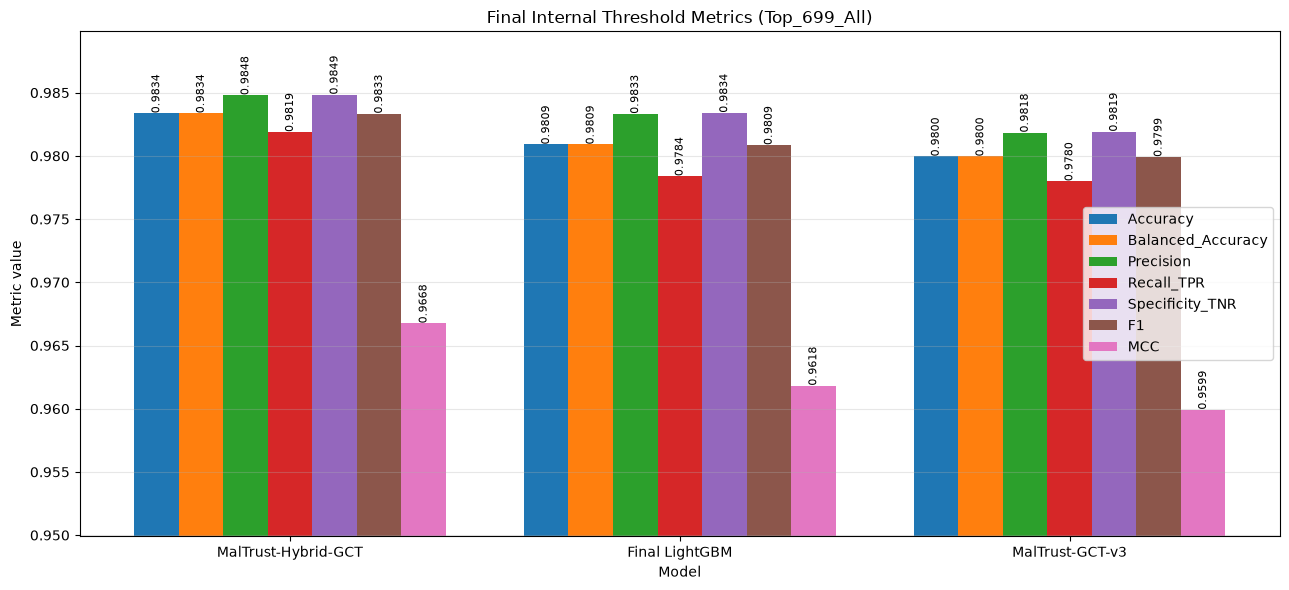

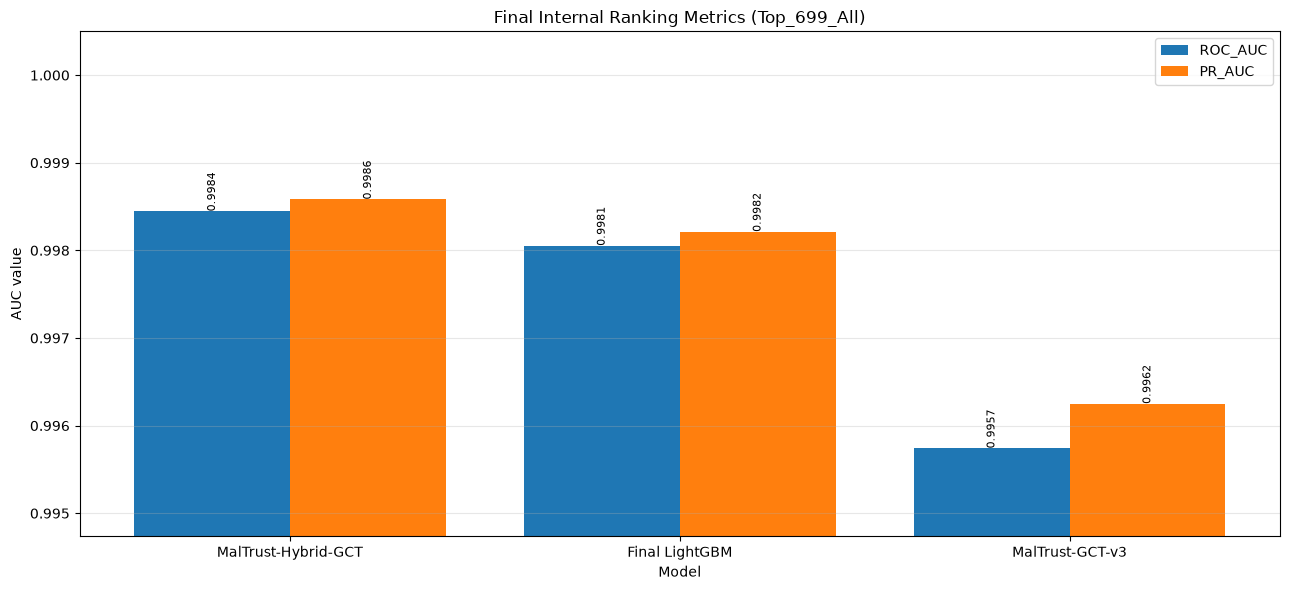

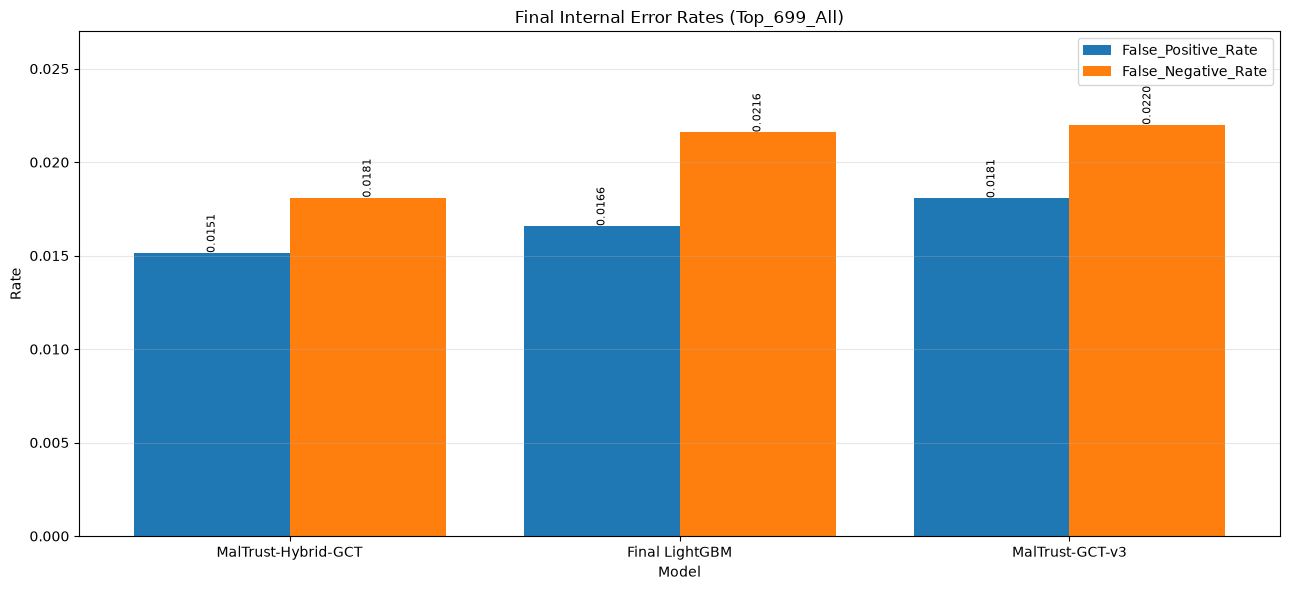

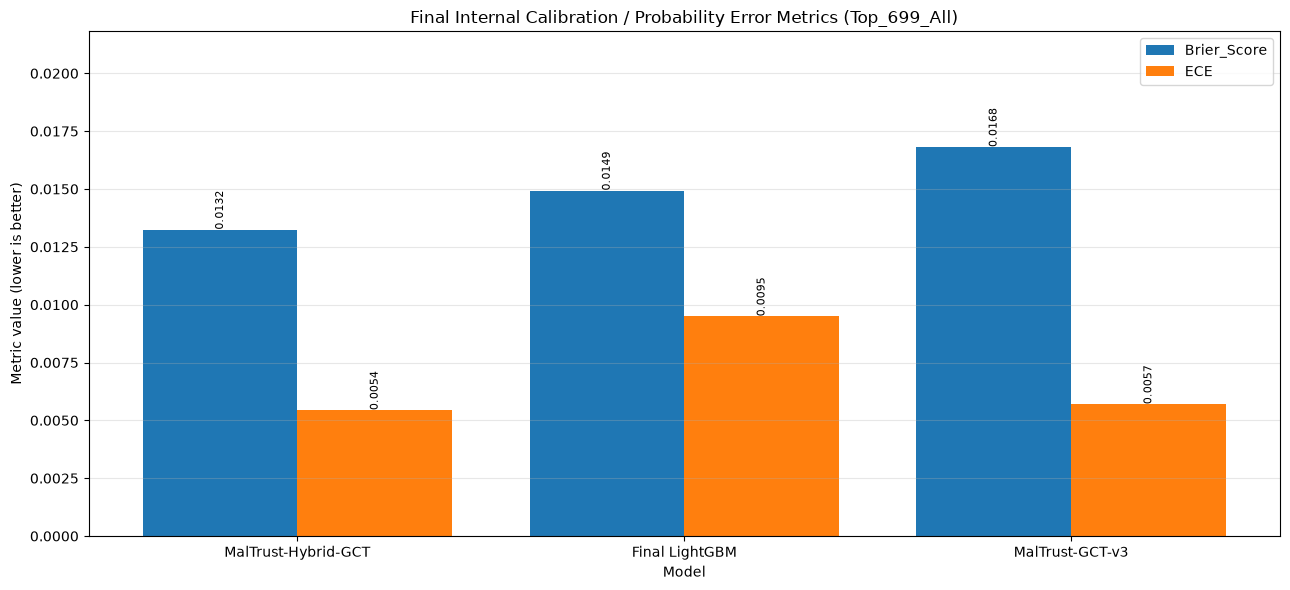

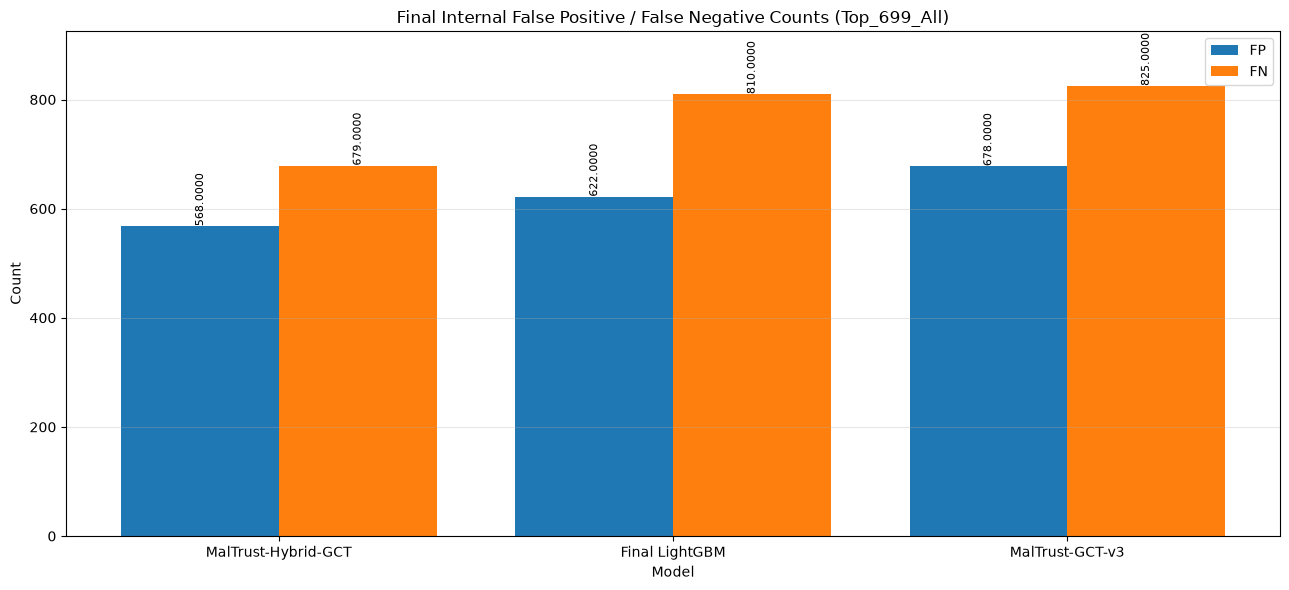

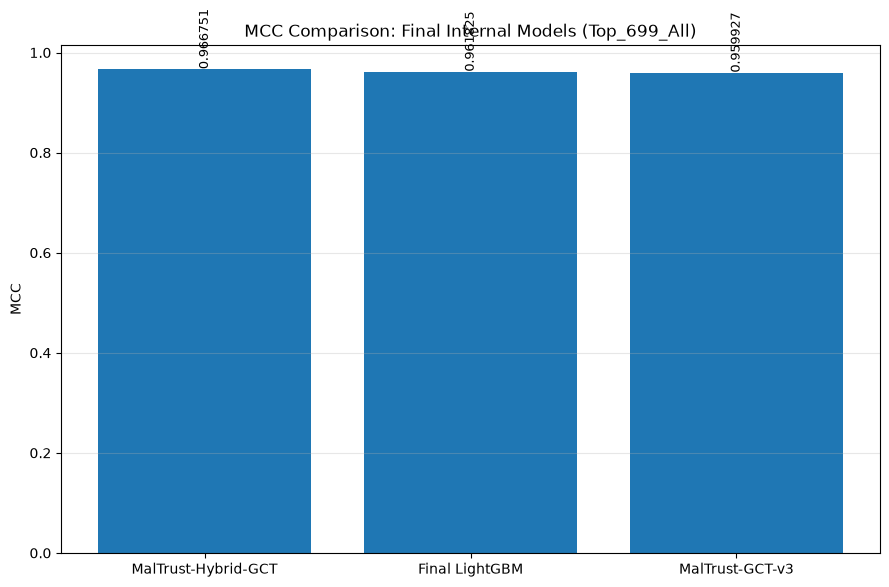

Non-fatal mirror-copy warning for C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell18_final_metric_comparison\revised_strict_clean_699\Top_699_All\figures\cell18_threshold_metric_comparison_top_699_all.png: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\figures\\cell18_final_metric_comparison\\figures\\cell18_threshold_metric_comparison_top_699_all.png'
Non-fatal mirror-copy warning for C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell18_final_metric_comparison\revised_strict_clean_699\Top_699_All\figures\cell18_auc_metric_comparison_top_699_all.png: [Errno 2] No such file or directory: 'C:\\User\\LENOVO\\Desktop\\Maltrust_xai_artifacts\\cell5_framework_artifacts\\final_framework_package\\revised_strict_clean_699\\Top_699_All\\maltrust_hybrid_gct_internal_package\\

In [38]:

# ============================================================
# MalTrust-XAI | Cell 18
# Final Internal Model Metric Comparison Graphs,
# Hybrid-GCT Gain Tables, and Manuscript-Ready Figure Export
#
# Corrected:
# - Compares MalTrust-Hybrid-GCT vs Final LightGBM vs MalTrust-GCT-v3
# - Uses Cell 15 / Cell 14 final internal model metrics
# - Does NOT use old validation feature-subset comparison logic
# - Uses a SHORT primary artifact directory to avoid Windows path-length failures
# - Creates directories before every save
# - No .tmp atomic saving
# ============================================================

try:
    debug("Generating final internal model metric comparison figures for Hybrid-GCT package...")
except Exception:
    pass

import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)


# ------------------------------------------------------------
# Safe helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_save_figure(path, dpi=300):
    ensure_parent_dir(path)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")


def safe_sha256(path):
    try:
        if path is None or not os.path.exists(path) or os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def register_artifact(artifact_name, artifact_path, source_path=None, status="generated"):
    if artifact_path is None or not os.path.exists(artifact_path):
        return None

    return {
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "source_path": source_path,
        "artifact_type": "directory" if os.path.isdir(artifact_path) else "file",
        "sha256": safe_sha256(artifact_path),
        "registered_at": now_str(),
        "status": status,
    }


def infer_existing_path_from_config(key_candidates):
    for key in key_candidates:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value
    return None


def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())
        if count == 0:
            continue

        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        weight = count / len(y_true)
        ece += weight * abs(observed_frequency - mean_confidence)

    return float(ece)


def evaluate_binary_predictions(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
        "PR_AUC": float(average_precision_score(y_true, y_prob)),
        "Brier_Score": float(brier_score_loss(y_true, y_prob)),
        "ECE": float(compute_ece(y_true, y_prob)),
        "False_Positive_Rate": float(fpr),
        "False_Negative_Rate": float(fnr),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def copy_to_package_if_possible(src_path, dst_dir):
    """Non-fatal copy from short Cell 18 path into final Cell 15 package."""
    try:
        if src_path is None or not os.path.exists(src_path) or os.path.isdir(src_path):
            return None
        ensure_dir(dst_dir)
        dst_path = os.path.join(dst_dir, os.path.basename(src_path))
        if os.path.abspath(src_path) != os.path.abspath(dst_path):
            shutil.copy2(src_path, dst_path)
        return dst_path
    except Exception as e:
        print(f"Non-fatal mirror-copy warning for {src_path}: {e}")
        return None


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG", "sha256_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All"),
        )
    )

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"

# Important correction:
# Use a short primary artifact path. The previous path nested inside the final package
# can exceed Windows path limits and cause FileNotFoundError even after mkdir.
CELL18_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell18_final_metric_comparison",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)

FIGURE_DIR = os.path.join(CELL18_ARTIFACT_DIR, "figures")
TABLE_DIR = os.path.join(CELL18_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL18_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL18_ARTIFACT_DIR, "configs")

for directory in [CELL18_ARTIFACT_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(directory)

# Optional mirror inside Cell 15 package. Copy failures are non-fatal.
CELL15_PACKAGE_DIR = EXPERIMENT_CONFIG.get("cell15_package_directory", None)
if isinstance(CELL15_PACKAGE_DIR, str) and os.path.exists(CELL15_PACKAGE_DIR):
    PACKAGE_MIRROR_DIR = os.path.join(CELL15_PACKAGE_DIR, "figures", "cell18_final_metric_comparison")
    PACKAGE_MIRROR_FIGURE_DIR = os.path.join(PACKAGE_MIRROR_DIR, "figures")
    PACKAGE_MIRROR_TABLE_DIR = os.path.join(PACKAGE_MIRROR_DIR, "tables")
    PACKAGE_MIRROR_REPORT_DIR = os.path.join(PACKAGE_MIRROR_DIR, "reports")
else:
    PACKAGE_MIRROR_DIR = None
    PACKAGE_MIRROR_FIGURE_DIR = None
    PACKAGE_MIRROR_TABLE_DIR = None
    PACKAGE_MIRROR_REPORT_DIR = None

print("Cell 18 context:")
print("Purpose: Final internal model metric comparison graphs")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Primary short artifact directory:", CELL18_ARTIFACT_DIR)
print("Optional package mirror directory:", PACKAGE_MIRROR_DIR)


# ------------------------------------------------------------
# Resolve final internal metrics table
# ------------------------------------------------------------
metric_source = None

if "final_manuscript_ready_results_df" in globals():
    metric_df = final_manuscript_ready_results_df.copy()
    metric_source = "in_memory_final_manuscript_ready_results_df"
elif "final_internal_results_df" in globals():
    metric_df = final_internal_results_df.copy()
    metric_source = "in_memory_final_internal_results_df"
elif "final_internal_model_metrics_df" in globals():
    metric_df = final_internal_model_metrics_df.copy()
    metric_source = "in_memory_final_internal_model_metrics_df"
else:
    metric_path = infer_existing_path_from_config([
        "cell15_manuscript_ready_results_path",
        "cell15_final_internal_results_path",
        "cell14_internal_model_metrics_path",
    ])
    if metric_path is not None:
        metric_df = pd.read_csv(metric_path)
        metric_source = metric_path
    else:
        metric_df = None

# Last fallback: compute directly from prediction table.
if metric_df is None:
    if "final_hybrid_predictions_df" in globals():
        pred_df = final_hybrid_predictions_df.copy()
        metric_source = "computed_from_in_memory_final_hybrid_predictions_df"
    elif "hybrid_predictions" in globals():
        pred_df = hybrid_predictions.copy()
        metric_source = "computed_from_in_memory_hybrid_predictions"
    else:
        pred_path = infer_existing_path_from_config([
            "cell15_hybrid_predictions_export_path",
            "maltrust_hybrid_gct_predictions_path",
            "cell11f_hybrid_gct_predictions_path",
            "cell11f_hybrid_predictions_path",
        ])
        if pred_path is None:
            raise FileNotFoundError(
                "Could not resolve Cell 15 metric table or Hybrid-GCT prediction table. "
                "Run Cells 11F and 15 first."
            )
        pred_df = pd.read_csv(pred_path)
        metric_source = f"computed_from_{pred_path}"

    required_pred_cols = [
        "y_true",
        "lgbm_score",
        "gct_score",
        "hybrid_score",
        "lgbm_pred",
        "gct_pred",
        "hybrid_pred",
    ]
    missing_pred_cols = [c for c in required_pred_cols if c not in pred_df.columns]
    if missing_pred_cols:
        raise ValueError(f"Prediction table missing required columns: {missing_pred_cols}")

    specs = {
        "MalTrust-Hybrid-GCT": {
            "role": "Final hybrid meta-detector",
            "score_col": "hybrid_score",
            "pred_col": "hybrid_pred",
        },
        "Final LightGBM": {
            "role": "Final standalone detector",
            "score_col": "lgbm_score",
            "pred_col": "lgbm_pred",
        },
        "MalTrust-GCT-v3": {
            "role": "Group-aware neural auxiliary detector",
            "score_col": "gct_score",
            "pred_col": "gct_pred",
        },
    }

    rows = []
    for model_name, spec in specs.items():
        payload = evaluate_binary_predictions(
            y_true=pred_df["y_true"].astype(int).values,
            y_pred=pred_df[spec["pred_col"]].astype(int).values,
            y_prob=pred_df[spec["score_col"]].astype(float).values,
        )
        rows.append({
            "Model": model_name,
            "Model_Role": spec["role"],
            "Samples": int(len(pred_df)),
            **payload,
        })

    metric_df = pd.DataFrame(rows)

# Normalize expected names.
if "F1_Score" in metric_df.columns and "F1" not in metric_df.columns:
    metric_df["F1"] = metric_df["F1_Score"]
if "Recall" in metric_df.columns and "Recall_TPR" not in metric_df.columns:
    metric_df["Recall_TPR"] = metric_df["Recall"]
if "Specificity" in metric_df.columns and "Specificity_TNR" not in metric_df.columns:
    metric_df["Specificity_TNR"] = metric_df["Specificity"]

required_metric_cols = [
    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate",
    "TN",
    "FP",
    "FN",
    "TP",
]
missing_metric_cols = [c for c in required_metric_cols if c not in metric_df.columns]
if missing_metric_cols:
    raise ValueError(f"Final metric table missing required columns: {missing_metric_cols}")

primary_models = ["MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"]
metric_df["Model"] = metric_df["Model"].astype(str)
plot_df = metric_df[metric_df["Model"].isin(primary_models)].copy()

missing_models = [m for m in primary_models if m not in set(plot_df["Model"])]
if missing_models:
    raise ValueError(f"Final metric table missing final comparison models: {missing_models}")

model_order = {model: i for i, model in enumerate(primary_models)}
plot_df["Model_Order"] = plot_df["Model"].map(model_order)
plot_df = plot_df.sort_values("Model_Order").reset_index(drop=True)
plot_df["Overall_Rank_By_MCC"] = plot_df["MCC"].rank(ascending=False, method="min").astype(int)

print("\nFinal model metric table used by Cell 18:")
display(plot_df)


# ------------------------------------------------------------
# Build gain / delta tables
# ------------------------------------------------------------
metric_direction = {
    "Accuracy": "higher_better",
    "Balanced_Accuracy": "higher_better",
    "Precision": "higher_better",
    "Recall_TPR": "higher_better",
    "Specificity_TNR": "higher_better",
    "F1": "higher_better",
    "MCC": "higher_better",
    "ROC_AUC": "higher_better",
    "PR_AUC": "higher_better",
    "Brier_Score": "lower_better",
    "ECE": "lower_better",
    "False_Positive_Rate": "lower_better",
    "False_Negative_Rate": "lower_better",
}

hybrid_row = plot_df[plot_df["Model"] == "MalTrust-Hybrid-GCT"].iloc[0]
delta_rows = []

for baseline in ["Final LightGBM", "MalTrust-GCT-v3"]:
    baseline_row = plot_df[plot_df["Model"] == baseline].iloc[0]
    for metric, direction in metric_direction.items():
        hybrid_value = float(hybrid_row[metric])
        baseline_value = float(baseline_row[metric])
        raw_delta = hybrid_value - baseline_value

        if direction == "higher_better":
            improvement = raw_delta
            hybrid_better = improvement > 0
        else:
            improvement = baseline_value - hybrid_value
            hybrid_better = improvement > 0

        delta_rows.append({
            "Comparison": f"MalTrust-Hybrid-GCT minus {baseline}",
            "Baseline_Model": baseline,
            "Metric": metric,
            "Direction": direction,
            "Hybrid_Value": hybrid_value,
            "Baseline_Value": baseline_value,
            "Raw_Delta_Hybrid_Minus_Baseline": raw_delta,
            "Improvement_In_Favorable_Direction": improvement,
            "Hybrid_Better": bool(hybrid_better),
        })

delta_df = pd.DataFrame(delta_rows)

ranking_df = plot_df.sort_values(
    by=["MCC", "F1", "Accuracy", "ROC_AUC", "PR_AUC"],
    ascending=[False, False, False, False, False],
).reset_index(drop=True)
ranking_df["Cell18_Rank"] = np.arange(1, len(ranking_df) + 1)

print("\nHybrid-GCT gain table:")
display(delta_df)

print("\nCell 18 final model ranking:")
display(ranking_df)


# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------
metric_table_path = os.path.join(TABLE_DIR, "cell18_final_internal_model_metric_table.csv")
ranking_table_path = os.path.join(TABLE_DIR, "cell18_final_internal_model_ranking_table.csv")
delta_table_path = os.path.join(TABLE_DIR, "cell18_hybrid_gct_metric_gain_table.csv")

safe_save_csv(plot_df.drop(columns=["Model_Order"], errors="ignore"), metric_table_path, index=False)
safe_save_csv(ranking_df.drop(columns=["Model_Order"], errors="ignore"), ranking_table_path, index=False)
safe_save_csv(delta_df, delta_table_path, index=False)

if PACKAGE_MIRROR_TABLE_DIR is not None:
    copy_to_package_if_possible(metric_table_path, PACKAGE_MIRROR_TABLE_DIR)
    copy_to_package_if_possible(ranking_table_path, PACKAGE_MIRROR_TABLE_DIR)
    copy_to_package_if_possible(delta_table_path, PACKAGE_MIRROR_TABLE_DIR)


# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------
def plot_grouped_bar(df, metrics, title, ylabel, output_path, ylim=None, rotate=0):
    ensure_parent_dir(output_path)

    x = np.arange(len(df))
    width = 0.80 / max(1, len(metrics))
    fig, ax = plt.subplots(figsize=(13, 6))

    for idx, metric in enumerate(metrics):
        values = df[metric].astype(float).values
        ax.bar(x + idx * width, values, width, label=metric)

        for j, value in enumerate(values):
            ax.text(
                x[j] + idx * width,
                value,
                f"{value:.4f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x + width * (len(metrics) - 1) / 2)
    ax.set_xticklabels(df["Model"].astype(str).tolist(), rotation=rotate)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(loc="best")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    safe_save_figure(output_path, dpi=300)
    plt.show()
    plt.close()


def plot_single_metric_bar(df, metric, title, ylabel, output_path, lower_is_better=False):
    ensure_parent_dir(output_path)

    fig, ax = plt.subplots(figsize=(9, 6))
    values = df[metric].astype(float).values
    ax.bar(df["Model"].astype(str).tolist(), values)

    for idx, value in enumerate(values):
        ax.text(idx, value, f"{value:.6f}", ha="center", va="bottom", fontsize=9, rotation=90)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    if lower_is_better:
        ax.text(0.02, 0.95, "Lower is better", transform=ax.transAxes, va="top")

    plt.xticks(rotation=0)
    plt.tight_layout()
    safe_save_figure(output_path, dpi=300)
    plt.show()
    plt.close()


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------
threshold_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
]
auc_metrics = ["ROC_AUC", "PR_AUC"]
error_metrics = ["False_Positive_Rate", "False_Negative_Rate"]
calibration_metrics = ["Brier_Score", "ECE"]
confusion_count_metrics = ["FP", "FN"]

threshold_metric_figure_path = os.path.join(
    FIGURE_DIR,
    f"cell18_threshold_metric_comparison_{FINAL_FEATURE_SET_NAME.lower()}.png",
)
auc_metric_figure_path = os.path.join(
    FIGURE_DIR,
    f"cell18_auc_metric_comparison_{FINAL_FEATURE_SET_NAME.lower()}.png",
)
error_rate_figure_path = os.path.join(
    FIGURE_DIR,
    f"cell18_error_rate_comparison_{FINAL_FEATURE_SET_NAME.lower()}.png",
)
calibration_figure_path = os.path.join(
    FIGURE_DIR,
    f"cell18_calibration_metric_comparison_{FINAL_FEATURE_SET_NAME.lower()}.png",
)
confusion_error_count_figure_path = os.path.join(
    FIGURE_DIR,
    f"cell18_fp_fn_count_comparison_{FINAL_FEATURE_SET_NAME.lower()}.png",
)
mcc_single_figure_path = os.path.join(
    FIGURE_DIR,
    f"cell18_mcc_comparison_{FINAL_FEATURE_SET_NAME.lower()}.png",
)

threshold_min = max(0.0, float(plot_df[threshold_metrics].min().min()) - 0.01)
threshold_max = min(1.005, float(plot_df[threshold_metrics].max().max()) + 0.005)

plot_grouped_bar(
    df=plot_df,
    metrics=threshold_metrics,
    title=f"Final Internal Threshold Metrics ({FINAL_FEATURE_SET_NAME})",
    ylabel="Metric value",
    output_path=threshold_metric_figure_path,
    ylim=(threshold_min, threshold_max),
)

plot_grouped_bar(
    df=plot_df,
    metrics=auc_metrics,
    title=f"Final Internal Ranking Metrics ({FINAL_FEATURE_SET_NAME})",
    ylabel="AUC value",
    output_path=auc_metric_figure_path,
    ylim=(max(0.99, float(plot_df[auc_metrics].min().min()) - 0.001), 1.0005),
)

plot_grouped_bar(
    df=plot_df,
    metrics=error_metrics,
    title=f"Final Internal Error Rates ({FINAL_FEATURE_SET_NAME})",
    ylabel="Rate",
    output_path=error_rate_figure_path,
    ylim=(0.0, float(plot_df[error_metrics].max().max()) + 0.005),
)

plot_grouped_bar(
    df=plot_df,
    metrics=calibration_metrics,
    title=f"Final Internal Calibration / Probability Error Metrics ({FINAL_FEATURE_SET_NAME})",
    ylabel="Metric value (lower is better)",
    output_path=calibration_figure_path,
    ylim=(0.0, float(plot_df[calibration_metrics].max().max()) + 0.005),
)

plot_grouped_bar(
    df=plot_df,
    metrics=confusion_count_metrics,
    title=f"Final Internal False Positive / False Negative Counts ({FINAL_FEATURE_SET_NAME})",
    ylabel="Count",
    output_path=confusion_error_count_figure_path,
    ylim=(0.0, float(plot_df[confusion_count_metrics].max().max()) + 100),
)

plot_single_metric_bar(
    df=plot_df,
    metric="MCC",
    title=f"MCC Comparison: Final Internal Models ({FINAL_FEATURE_SET_NAME})",
    ylabel="MCC",
    output_path=mcc_single_figure_path,
)

if PACKAGE_MIRROR_FIGURE_DIR is not None:
    for fig_path in [
        threshold_metric_figure_path,
        auc_metric_figure_path,
        error_rate_figure_path,
        calibration_figure_path,
        confusion_error_count_figure_path,
        mcc_single_figure_path,
    ]:
        copy_to_package_if_possible(fig_path, PACKAGE_MIRROR_FIGURE_DIR)


# ------------------------------------------------------------
# Report and artifact index
# ------------------------------------------------------------
cell18_report_path = os.path.join(REPORT_DIR, "cell18_final_metric_comparison_report.json")

better_vs_lightgbm = delta_df[
    (delta_df["Baseline_Model"] == "Final LightGBM") &
    (delta_df["Hybrid_Better"] == True)
]["Metric"].tolist()

better_vs_gct = delta_df[
    (delta_df["Baseline_Model"] == "MalTrust-GCT-v3") &
    (delta_df["Hybrid_Better"] == True)
]["Metric"].tolist()

cell18_report = {
    "cell": "Cell 18",
    "cell_name": "Final Internal Model Metric Comparison Graphs",
    "corrected_purpose": "Hybrid-GCT vs Final LightGBM vs MalTrust-GCT-v3 final internal comparison",
    "replaced_old_purpose": "Validation-based compact feature-subset comparison",
    "path_policy": "Primary Cell 18 artifacts are saved to a short path to avoid Windows path-length failures.",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "metric_source": metric_source,
    "models_compared": primary_models,
    "best_model_by_mcc": str(ranking_df.iloc[0]["Model"]),
    "hybrid_better_than_final_lightgbm_metrics": better_vs_lightgbm,
    "hybrid_better_than_gct_v3_metrics": better_vs_gct,
    "metric_table_path": metric_table_path,
    "ranking_table_path": ranking_table_path,
    "delta_table_path": delta_table_path,
    "figures": {
        "threshold_metric_comparison": threshold_metric_figure_path,
        "auc_metric_comparison": auc_metric_figure_path,
        "error_rate_comparison": error_rate_figure_path,
        "calibration_metric_comparison": calibration_figure_path,
        "fp_fn_count_comparison": confusion_error_count_figure_path,
        "mcc_comparison": mcc_single_figure_path,
    },
    "optional_final_package_mirror_directory": PACKAGE_MIRROR_DIR,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

safe_save_json(cell18_report, cell18_report_path)

if PACKAGE_MIRROR_REPORT_DIR is not None:
    copy_to_package_if_possible(cell18_report_path, PACKAGE_MIRROR_REPORT_DIR)

cell18_artifacts = {
    "metric_table": metric_table_path,
    "ranking_table": ranking_table_path,
    "hybrid_gain_table": delta_table_path,
    "threshold_metric_comparison_figure": threshold_metric_figure_path,
    "auc_metric_comparison_figure": auc_metric_figure_path,
    "error_rate_comparison_figure": error_rate_figure_path,
    "calibration_metric_comparison_figure": calibration_figure_path,
    "fp_fn_count_comparison_figure": confusion_error_count_figure_path,
    "mcc_comparison_figure": mcc_single_figure_path,
    "final_metric_comparison_report": cell18_report_path,
}

cell18_artifact_rows = []
for artifact_name, artifact_path in cell18_artifacts.items():
    row = register_artifact(artifact_name, artifact_path)
    if row is not None:
        cell18_artifact_rows.append(row)

cell18_artifact_hashes_path = os.path.join(CELL18_ARTIFACT_DIR, "cell18_artifact_hashes.csv")
safe_save_csv(pd.DataFrame(cell18_artifact_rows), cell18_artifact_hashes_path, index=False)

hashes_row = register_artifact("cell18_artifact_hashes", cell18_artifact_hashes_path)
if hashes_row is not None:
    cell18_artifact_rows.append(hashes_row)

cell18_artifact_index = {
    "cell": "Cell 18",
    "cell_name": "Final Internal Model Metric Comparison Graphs",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "primary_artifact_directory": CELL18_ARTIFACT_DIR,
    "optional_final_package_mirror_directory": PACKAGE_MIRROR_DIR,
    "artifacts": cell18_artifact_rows,
    "artifact_hash_report_path": cell18_artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(cell18_artifact_hashes_path),
}

cell18_artifact_index_path = os.path.join(CELL18_ARTIFACT_DIR, "cell18_artifact_index.json")
safe_save_json(cell18_artifact_index, cell18_artifact_index_path)
cell18_artifact_index_hash = safe_sha256(cell18_artifact_index_path)


# ------------------------------------------------------------
# Update experiment config
# ------------------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell18_corrected_purpose"] = "Final internal model metric comparison graphs"
    EXPERIMENT_CONFIG["cell18_path_policy"] = "short_primary_path_to_avoid_windows_max_path_failures"
    EXPERIMENT_CONFIG["cell18_metric_source"] = metric_source
    EXPERIMENT_CONFIG["cell18_primary_artifact_dir"] = CELL18_ARTIFACT_DIR
    EXPERIMENT_CONFIG["cell18_optional_package_mirror_dir"] = PACKAGE_MIRROR_DIR
    EXPERIMENT_CONFIG["cell18_metric_table_path"] = metric_table_path
    EXPERIMENT_CONFIG["cell18_ranking_table_path"] = ranking_table_path
    EXPERIMENT_CONFIG["cell18_hybrid_gain_table_path"] = delta_table_path
    EXPERIMENT_CONFIG["cell18_threshold_metric_figure_path"] = threshold_metric_figure_path
    EXPERIMENT_CONFIG["cell18_auc_metric_figure_path"] = auc_metric_figure_path
    EXPERIMENT_CONFIG["cell18_error_rate_figure_path"] = error_rate_figure_path
    EXPERIMENT_CONFIG["cell18_calibration_figure_path"] = calibration_figure_path
    EXPERIMENT_CONFIG["cell18_fp_fn_count_figure_path"] = confusion_error_count_figure_path
    EXPERIMENT_CONFIG["cell18_mcc_figure_path"] = mcc_single_figure_path
    EXPERIMENT_CONFIG["cell18_report_path"] = cell18_report_path
    EXPERIMENT_CONFIG["cell18_artifact_hashes_path"] = cell18_artifact_hashes_path
    EXPERIMENT_CONFIG["cell18_artifact_index_path"] = cell18_artifact_index_path
    EXPERIMENT_CONFIG["cell18_artifact_index_sha256"] = cell18_artifact_index_hash

    post_cell18_config_path = os.path.join(CONFIG_DIR, "cell18_experiment_config_snapshot.json")
    safe_save_json(EXPERIMENT_CONFIG, post_cell18_config_path)
    post_cell18_config_hash = safe_sha256(post_cell18_config_path)
    EXPERIMENT_CONFIG["cell18_experiment_config_snapshot_path"] = post_cell18_config_path
    EXPERIMENT_CONFIG["cell18_experiment_config_snapshot_sha256"] = post_cell18_config_hash

    print("\nPost-Cell-18 experiment configuration snapshot saved to:", post_cell18_config_path)
    print("Post-Cell-18 experiment configuration snapshot SHA-256:", post_cell18_config_hash)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------------------
# Aliases and assertions
# ------------------------------------------------------------
final_metric_comparison_plot_df = plot_df
final_metric_comparison_ranking_df = ranking_df
final_hybrid_gain_df = delta_df

assert str(ranking_df.iloc[0]["Model"]) == "MalTrust-Hybrid-GCT", (
    "MalTrust-Hybrid-GCT should rank first by MCC in Cell 18."
)
assert os.path.exists(metric_table_path), "Metric table was not saved."
assert os.path.exists(ranking_table_path), "Ranking table was not saved."
assert os.path.exists(delta_table_path), "Hybrid gain table was not saved."
assert os.path.exists(threshold_metric_figure_path), "Threshold metric comparison figure was not saved."
assert os.path.exists(auc_metric_figure_path), "AUC metric comparison figure was not saved."
assert os.path.exists(error_rate_figure_path), "Error-rate comparison figure was not saved."
assert os.path.exists(calibration_figure_path), "Calibration metric comparison figure was not saved."
assert os.path.exists(confusion_error_count_figure_path), "FP/FN count figure was not saved."
assert os.path.exists(mcc_single_figure_path), "MCC comparison figure was not saved."
assert os.path.exists(cell18_artifact_index_path), "Cell 18 artifact index was not saved."

print("\nCell 18 completed successfully.")
print("Purpose: Final internal model metric comparison graphs")
print("Best model by MCC:", ranking_df.iloc[0]["Model"])
print("Primary artifact directory:", CELL18_ARTIFACT_DIR)
print("Metric table:", metric_table_path)
print("Hybrid gain table:", delta_table_path)
print("Artifact index:", cell18_artifact_index_path)
print("Artifact index SHA-256:", cell18_artifact_index_hash)

try:
    debug("Final internal model metric comparison cell completed successfully.")
except Exception:
    pass


# ============================================================
# Updated Cell 19: Final 500K Cross-Validation
# Purpose:
# 1. Validate robustness of MalTrust-XAI on Top-256 features.
# 2. Generate mean and standard deviation metrics.
# 3. Save /thesis-ready cross-validation table.
# ============================================================

In [39]:
# ============================================================
# MalTrust-XAI | Cell 19
# Standalone Final LightGBM Training-Split Cross-Validation
# Fold-Level Metrics, Confidence Intervals, and Artifact Hashing
#
# Corrected purpose after Hybrid-GCT integration:
# - This cell is NOT the final Hybrid-GCT held-out evaluation.
# - This cell audits training-split stability of the standalone Final LightGBM detector.
# - Final Hybrid-GCT superiority is already established by Cells 14, 15, 17, and 18.
# - No validation or test split is used here.
# - Direct safe saving only; no .tmp files.
# ============================================================

try:
    debug("Starting standalone Final LightGBM training-split cross-validation audit...")
except Exception:
    pass

import os
import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)


# ------------------------------------------------------------
# Safe helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_sha256(path):
    try:
        if path is None or not os.path.exists(path) or os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def register_artifact(artifact_name, artifact_path, source_path=None, status="generated"):
    if artifact_path is None or not os.path.exists(artifact_path):
        return None
    return {
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "source_path": source_path,
        "artifact_type": "directory" if os.path.isdir(artifact_path) else "file",
        "sha256": safe_sha256(artifact_path),
        "registered_at": now_str(),
        "status": status,
    }


def infer_existing_path_from_config(key_candidates):
    for key in key_candidates:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value
    return None


def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            continue

        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        weight = count / len(y_true)
        ece += weight * abs(observed_frequency - mean_confidence)

    return float(ece)


def evaluate_fold_predictions(y_true, y_pred, y_prob):
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)
    y_prob = pd.Series(y_prob).astype(float).reset_index(drop=True)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
        "PR_AUC": float(average_precision_score(y_true, y_prob)),
        "Brier_Score": float(brier_score_loss(y_true, y_prob)),
        "ECE": float(compute_ece(y_true, y_prob)),
        "False_Positive_Rate": float(false_positive_rate),
        "False_Negative_Rate": float(false_negative_rate),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def mean_ci_95(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    mean_value = float(np.mean(values))
    std_value = float(np.std(values, ddof=1)) if n > 1 else 0.0
    se_value = std_value / np.sqrt(n) if n > 1 else 0.0

    t_crit_lookup = {
        2: 12.706,
        3: 4.303,
        4: 3.182,
        5: 2.776,
        6: 2.571,
        7: 2.447,
        8: 2.365,
        9: 2.306,
        10: 2.262,
    }

    t_crit = t_crit_lookup.get(n, 1.96)
    ci_lower = mean_value - t_crit * se_value
    ci_upper = mean_value + t_crit * se_value

    return float(mean_value), float(std_value), float(ci_lower), float(ci_upper)


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = [
    "X_train_s",
    "y_train_s",
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG",
    "sha256_file",
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required objects from previous cells are missing: {missing_globals}")


# ------------------------------------------------------------
# Context
# ------------------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All"),
        )
    )

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))
N_FOLDS = int(EXPERIMENT_CONFIG.get("cross_validation_folds", 5))

NUM_TRAIN_FILES_CELL19 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50),
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL19 * 10000,
    )
)

TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))
EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))

print("Cell 19 context:")
print("Purpose: standalone Final LightGBM training-split CV stability audit")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final selected subset:", FINAL_FEATURE_SET_NAME)
print("Expected training rows:", EXPECTED_TRAIN_ROWS)
print("Actual training shape:", X_train_s.shape)
print("CV folds:", N_FOLDS)


# ------------------------------------------------------------
# Resolve final selected features
# ------------------------------------------------------------
if "final_selected_features" in globals():
    FINAL_FEATURES = list(final_selected_features)
elif "X_test_final_s" in globals():
    FINAL_FEATURES = list(X_test_final_s.columns)
else:
    final_feature_path = infer_existing_path_from_config([
        "cell15_features_joblib_path",
        "cell11_final_selected_features_path",
        "cell12_final_selected_features_path",
    ])

    if final_feature_path and final_feature_path.endswith(".joblib"):
        FINAL_FEATURES = list(joblib.load(final_feature_path))
    elif "subset_feature_lists" in globals() and FINAL_FEATURE_SET_NAME in subset_feature_lists:
        FINAL_FEATURES = list(subset_feature_lists[FINAL_FEATURE_SET_NAME])
    elif "strict_feature_subsets" in globals() and FINAL_FEATURE_SET_NAME in strict_feature_subsets:
        payload = strict_feature_subsets[FINAL_FEATURE_SET_NAME]
        if isinstance(payload, dict) and "features" in payload:
            FINAL_FEATURES = list(payload["features"])
        else:
            raise ValueError("strict_feature_subsets exists but does not contain feature lists.")
    else:
        raise NameError("Final selected feature list not found. Run corrected Cell 10/11/15 first.")

FINAL_FEATURE_COUNT = int(len(FINAL_FEATURES))

missing_features = [f for f in FINAL_FEATURES if f not in X_train_s.columns]
if missing_features:
    raise ValueError(f"Final selected features missing from X_train_s: {missing_features[:20]}")

X_cv = X_train_s[FINAL_FEATURES].reset_index(drop=True)
y_cv = pd.Series(y_train_s).astype(int).reset_index(drop=True)

print("\nCV matrix:")
print("X_cv:", X_cv.shape)
print("y_cv:", y_cv.shape)
print("Label distribution:")
print(y_cv.value_counts().sort_index())

if len(X_cv) != len(y_cv):
    raise ValueError("X_cv and y_cv row counts differ.")

if set(y_cv.unique()) - {0, 1}:
    raise ValueError("y_cv contains labels outside {0, 1}.")

if X_cv.shape[1] != FINAL_FEATURE_COUNT:
    raise ValueError("CV feature-count mismatch.")

if X_train_s.shape[0] != EXPECTED_TRAIN_ROWS:
    print(
        f"Warning: expected {EXPECTED_TRAIN_ROWS} training rows from config, "
        f"but found {X_train_s.shape[0]}. Continuing with actual rows."
    )

label_counts = y_cv.value_counts().sort_index().to_dict()
if 0 in label_counts and 1 in label_counts and label_counts[0] != label_counts[1]:
    print("Warning: training split is not exactly class-balanced. Continuing with StratifiedKFold.")


# ------------------------------------------------------------
# Artifact directory
# ------------------------------------------------------------
CELL19_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell19_training_split_cv",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)

TABLE_DIR = os.path.join(CELL19_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL19_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL19_ARTIFACT_DIR, "configs")

for directory in [CELL19_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(directory)

print("\nCell 19 artifact directory:", CELL19_ARTIFACT_DIR)


# ------------------------------------------------------------
# CV model configuration
# ------------------------------------------------------------
cv_lightgbm_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 64,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "objective": "binary",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}


# ------------------------------------------------------------
# Stratified K-Fold CV
# ------------------------------------------------------------
skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_rows = []
cv_start = time.time()

for fold_id, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print("\n" + "=" * 80)
    print(f"Training standalone Final LightGBM CV fold {fold_id}/{N_FOLDS}")
    print("=" * 80)

    X_tr = X_cv.iloc[train_idx]
    X_va = X_cv.iloc[valid_idx]
    y_tr = y_cv.iloc[train_idx].reset_index(drop=True)
    y_va = y_cv.iloc[valid_idx].reset_index(drop=True)

    cv_model = LGBMClassifier(
        **{
            **cv_lightgbm_params,
            "random_state": RANDOM_STATE + fold_id,
        }
    )

    fold_train_start = time.time()
    cv_model.fit(X_tr, y_tr)
    fold_train_seconds = time.time() - fold_train_start

    y_pred = cv_model.predict(X_va)
    y_prob = cv_model.predict_proba(X_va)[:, 1]

    fold_metrics = evaluate_fold_predictions(y_va, y_pred, y_prob)

    row = {
        "Fold_ID": int(fold_id),
        "Model": "Final LightGBM",
        "Cell19_Role": "Standalone final LightGBM training-split CV audit",
        "Subset": FINAL_FEATURE_SET_NAME,
        "Feature_Count": int(FINAL_FEATURE_COUNT),
        "Train_Rows": int(len(train_idx)),
        "Validation_Rows": int(len(valid_idx)),
        "Training_Time_Seconds": float(fold_train_seconds),
    }

    row.update(fold_metrics)
    fold_rows.append(row)

    del X_tr, X_va, y_tr, y_va, cv_model, y_pred, y_prob
    gc.collect()

cv_runtime_seconds = time.time() - cv_start

cv_fold_results_df = pd.DataFrame(fold_rows)

print("\nFold-level cross-validation results:")
display(cv_fold_results_df)


# ------------------------------------------------------------
# Summarize CV metrics with 95% CI
# ------------------------------------------------------------
metrics_to_summarize = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate",
]

summary_rows = []

for metric in metrics_to_summarize:
    mean_value, std_value, ci_lower, ci_upper = mean_ci_95(cv_fold_results_df[metric].values)

    summary_rows.append({
        "Metric": metric,
        "Mean": float(mean_value),
        "Std_Deviation": float(std_value),
        "CI95_Lower": float(ci_lower),
        "CI95_Upper": float(ci_upper),
        "Fold_Count": int(N_FOLDS),
    })

cv_summary_df = pd.DataFrame(summary_rows)

print("\nStandalone Final LightGBM training-split CV summary:")
display(cv_summary_df)


# ------------------------------------------------------------
# Compare CV summary to final internal held-out results if available
# ------------------------------------------------------------
heldout_comparison_rows = []

if "final_internal_results_df" in globals():
    heldout_df = final_internal_results_df.copy()
elif "final_manuscript_ready_results_df" in globals():
    heldout_df = final_manuscript_ready_results_df.copy()
else:
    heldout_path = infer_existing_path_from_config([
        "cell15_final_internal_results_path",
        "cell15_manuscript_ready_results_path",
    ])
    heldout_df = pd.read_csv(heldout_path) if heldout_path is not None else pd.DataFrame()

if not heldout_df.empty and "Model" in heldout_df.columns:
    heldout_lgbm = heldout_df[heldout_df["Model"].astype(str) == "Final LightGBM"].copy()
    if not heldout_lgbm.empty:
        heldout_row = heldout_lgbm.iloc[0]
        for metric in metrics_to_summarize:
            if metric in heldout_row.index:
                cv_mean = float(cv_summary_df.loc[cv_summary_df["Metric"] == metric, "Mean"].iloc[0])
                heldout_value = float(heldout_row[metric])
                heldout_comparison_rows.append({
                    "Model": "Final LightGBM",
                    "Metric": metric,
                    "CV_Mean_Training_Split": cv_mean,
                    "Heldout_Internal_Test_Value": heldout_value,
                    "Heldout_Minus_CV_Mean": heldout_value - cv_mean,
                })

heldout_comparison_df = pd.DataFrame(heldout_comparison_rows)

if not heldout_comparison_df.empty:
    print("\nCV mean vs held-out internal Final LightGBM comparison:")
    display(heldout_comparison_df)


# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
cv_fold_results_path = os.path.join(
    TABLE_DIR,
    f"cell19_cv_fold_results_{FINAL_FEATURE_SET_NAME.lower()}.csv",
)

cv_summary_path = os.path.join(
    TABLE_DIR,
    f"cell19_cv_summary_{FINAL_FEATURE_SET_NAME.lower()}.csv",
)

heldout_comparison_path = os.path.join(
    TABLE_DIR,
    f"cell19_cv_vs_heldout_lightgbm_comparison_{FINAL_FEATURE_SET_NAME.lower()}.csv",
)

cv_report_path = os.path.join(
    REPORT_DIR,
    f"cell19_cv_report_{FINAL_FEATURE_SET_NAME.lower()}.json",
)

safe_save_csv(cv_fold_results_df, cv_fold_results_path, index=False)
safe_save_csv(cv_summary_df, cv_summary_path, index=False)

if not heldout_comparison_df.empty:
    safe_save_csv(heldout_comparison_df, heldout_comparison_path, index=False)
else:
    safe_save_csv(
        pd.DataFrame(columns=[
            "Model",
            "Metric",
            "CV_Mean_Training_Split",
            "Heldout_Internal_Test_Value",
            "Heldout_Minus_CV_Mean",
        ]),
        heldout_comparison_path,
        index=False,
    )

cv_report = {
    "cell": "Cell 19",
    "cell_name": "Standalone Final LightGBM Training-Split Cross-Validation",
    "corrected_purpose": "Training-split CV stability audit for standalone Final LightGBM",
    "not_final_hybrid_gct_evaluation": True,
    "hybrid_gct_final_evaluation_cells": ["Cell 14", "Cell 15", "Cell 17", "Cell 18"],
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "final_feature_count": int(FINAL_FEATURE_COUNT),
    "selected_train_files": int(NUM_TRAIN_FILES_CELL19),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "expected_train_rows_from_config": int(EXPECTED_TRAIN_ROWS),
    "actual_cv_rows": int(X_cv.shape[0]),
    "cv_uses_training_split_only": True,
    "validation_split_used": False,
    "test_split_used": False,
    "n_folds": int(N_FOLDS),
    "fold_results_path": cv_fold_results_path,
    "summary_path": cv_summary_path,
    "heldout_comparison_path": heldout_comparison_path,
    "lightgbm_params": cv_lightgbm_params,
    "runtime_seconds": float(cv_runtime_seconds),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

safe_save_json(cv_report, cv_report_path)


# ------------------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------------------
cell19_artifacts = {
    "cv_fold_results": cv_fold_results_path,
    "cv_summary": cv_summary_path,
    "cv_vs_heldout_lightgbm_comparison": heldout_comparison_path,
    "cv_report": cv_report_path,
}

cell19_artifact_rows = []

for artifact_name, artifact_path in cell19_artifacts.items():
    row = register_artifact(artifact_name, artifact_path)
    if row is not None:
        cell19_artifact_rows.append(row)

cell19_artifact_hashes_path = os.path.join(
    CELL19_ARTIFACT_DIR,
    "cell19_artifact_hashes.csv",
)

safe_save_csv(pd.DataFrame(cell19_artifact_rows), cell19_artifact_hashes_path, index=False)

hashes_row = register_artifact("cell19_artifact_hashes", cell19_artifact_hashes_path)
if hashes_row is not None:
    cell19_artifact_rows.append(hashes_row)

cell19_artifact_index = {
    "cell": "Cell 19",
    "cell_name": "Standalone Final LightGBM Training-Split Cross-Validation",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": cell19_artifact_rows,
    "artifact_hash_report_path": cell19_artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(cell19_artifact_hashes_path),
}

cell19_artifact_index_path = os.path.join(
    CELL19_ARTIFACT_DIR,
    "cell19_artifact_index.json",
)

safe_save_json(cell19_artifact_index, cell19_artifact_index_path)
cell19_artifact_index_hash = safe_sha256(cell19_artifact_index_path)

print("\nCell 19 artifact index:", cell19_artifact_index_path)
print("Cell 19 artifact index SHA-256:", cell19_artifact_index_hash)


# ------------------------------------------------------------
# Update experiment config
# ------------------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell19_corrected_purpose"] = "Standalone Final LightGBM training-split CV stability audit"
    EXPERIMENT_CONFIG["cell19_cv_fold_results_path"] = cv_fold_results_path
    EXPERIMENT_CONFIG["cell19_cv_summary_path"] = cv_summary_path
    EXPERIMENT_CONFIG["cell19_cv_vs_heldout_lightgbm_comparison_path"] = heldout_comparison_path
    EXPERIMENT_CONFIG["cell19_cv_report_path"] = cv_report_path
    EXPERIMENT_CONFIG["cell19_artifact_index_path"] = cell19_artifact_index_path
    EXPERIMENT_CONFIG["cell19_artifact_index_sha256"] = cell19_artifact_index_hash
    EXPERIMENT_CONFIG["cell19_cv_folds"] = int(N_FOLDS)
    EXPERIMENT_CONFIG["cell19_cv_uses_training_split_only"] = True
    EXPERIMENT_CONFIG["cell19_not_final_hybrid_gct_evaluation"] = True

    post_cell19_config_path = os.path.join(
        CONFIG_DIR,
        "cell19_experiment_config_snapshot.json",
    )

    safe_save_json(EXPERIMENT_CONFIG, post_cell19_config_path)
    post_cell19_config_hash = safe_sha256(post_cell19_config_path)

    EXPERIMENT_CONFIG["cell19_experiment_config_snapshot_path"] = post_cell19_config_path
    EXPERIMENT_CONFIG["cell19_experiment_config_snapshot_sha256"] = post_cell19_config_hash

    print("\nPost-Cell-19 experiment configuration snapshot saved to:", post_cell19_config_path)
    print("Post-Cell-19 experiment configuration snapshot SHA-256:", post_cell19_config_hash)

except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------------------
# Standard aliases
# ------------------------------------------------------------
final_lightgbm_cv_fold_results_df = cv_fold_results_df
final_lightgbm_cv_summary_df = cv_summary_df
final_lightgbm_cv_vs_heldout_df = heldout_comparison_df

# Legacy aliases retained for downstream compatibility.
final_subset_cv_fold_results_df = cv_fold_results_df
final_subset_cv_summary_df = cv_summary_df


# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------
assert len(cv_fold_results_df) == N_FOLDS, "Unexpected number of CV fold rows."
assert cv_fold_results_df["Validation_Rows"].sum() == len(y_cv), (
    "Each training row should appear once as validation across K folds."
)
assert os.path.exists(cv_summary_path), "CV summary was not saved."
assert os.path.exists(cv_fold_results_path), "CV fold results were not saved."
assert os.path.exists(cell19_artifact_index_path), "Cell 19 artifact index was not saved."

print("\nCell 19 completed successfully.")
print("Purpose: standalone Final LightGBM training-split CV stability audit")
print("This is not the final Hybrid-GCT evaluation.")
print("CV fold results:", cv_fold_results_path)
print("CV summary:", cv_summary_path)
print("Artifact index:", cell19_artifact_index_path)
print("Artifact index SHA-256:", cell19_artifact_index_hash)

try:
    debug("Standalone Final LightGBM training-split CV cell completed successfully.")
except Exception:
    pass


[DEBUG] 2026-06-24 10:35:18 | Starting standalone Final LightGBM training-split cross-validation audit...
Cell 19 context:
Purpose: standalone Final LightGBM training-split CV stability audit
Feature space: revised_strict_clean_699
Final selected subset: Top_699_All
Expected training rows: 350000
Actual training shape: (350000, 699)
CV folds: 5

CV matrix:
X_cv: (350000, 699)
y_cv: (350000,)
Label distribution:
label
0    175000
1    175000
Name: count, dtype: int64

Cell 19 artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell19_training_split_cv\revised_strict_clean_699\Top_699_All

Training standalone Final LightGBM CV fold 1/5

Training standalone Final LightGBM CV fold 2/5

Training standalone Final LightGBM CV fold 3/5

Training standalone Final LightGBM CV fold 4/5

Training standalone Final LightGBM CV fold 5/5

Fold-level cross-validation results:


,Fold_ID,Model,Cell19_Role,Subset,Feature_Count,Train_Rows,Validation_Rows,Training_Time_Seconds,Accuracy,Balanced_Accuracy,...,ROC_AUC,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP
0,1,Final LightGBM,Standalone final LightGBM training-split CV audit,Top_699_All,699,280000,70000,34.977100,0.980214,0.980214,...,0.998024,0.998178,0.015313,0.008836,0.016029,0.023543,34439,561,824,34176
1,2,Final LightGBM,Standalone final LightGBM training-split CV audit,Top_699_All,699,280000,70000,32.690404,0.980114,0.980114,...,0.998055,0.998193,0.015211,0.008997,0.016514,0.023257,34422,578,814,34186
2,3,Final LightGBM,Standalone final LightGBM training-split CV audit,Top_699_All,699,280000,70000,32.625691,0.979029,0.979029,...,0.997649,0.997873,0.016208,0.007793,0.018029,0.023914,34369,631,837,34163
3,4,Final LightGBM,Standalone final LightGBM training-split CV audit,Top_699_All,699,280000,70000,32.468588,0.979171,0.979171,...,0.997932,0.998086,0.015779,0.008257,0.016686,0.024971,34416,584,874,34126
4,5,Final LightGBM,Standalone final LightGBM training-split CV audit,Top_699_All,699,280000,70000,32.743063,0.980943,0.980943,...,0.998141,0.998286,0.014856,0.009561,0.016457,0.021657,34424,576,758,34242



Standalone Final LightGBM training-split CV summary:


,Metric,Mean,Std_Deviation,CI95_Lower,CI95_Upper,Fold_Count
0,Accuracy,0.979894,0.000794,0.978908,0.980880,5
1,Balanced_Accuracy,0.979894,0.000794,0.978908,0.980880,5
2,Precision,0.983144,0.000756,0.982205,0.984083,5
3,Recall_TPR,0.976531,0.001203,0.975038,0.978025,5
4,Specificity_TNR,0.983257,0.000758,0.982316,0.984199,5
5,F1,0.979826,0.000802,0.978830,0.980822,5
6,MCC,0.959811,0.001585,0.957843,0.961778,5
7,ROC_AUC,0.997960,0.000189,0.997725,0.998195,5
8,PR_AUC,0.998123,0.000157,0.997929,0.998318,5
9,Brier_Score,0.015473,0.000527,0.014819,0.016127,5



CV mean vs held-out internal Final LightGBM comparison:


,Model,Metric,CV_Mean_Training_Split,Heldout_Internal_Test_Value,Heldout_Minus_CV_Mean
0,Final LightGBM,Accuracy,0.979894,0.980907,0.001012
1,Final LightGBM,Balanced_Accuracy,0.979894,0.980907,0.001012
2,Final LightGBM,Precision,0.983144,0.983330,0.000186
3,Final LightGBM,Recall_TPR,0.976531,0.978400,0.001869
4,Final LightGBM,Specificity_TNR,0.983257,0.983413,0.000156
5,Final LightGBM,F1,0.979826,0.980859,0.001032
6,Final LightGBM,MCC,0.959811,0.961825,0.002015
7,Final LightGBM,ROC_AUC,0.997960,0.998052,0.000092
8,Final LightGBM,PR_AUC,0.998123,0.998211,0.000088
9,Final LightGBM,Brier_Score,0.015473,0.014934,-0.000539



Cell 19 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell19_training_split_cv\revised_strict_clean_699\Top_699_All\cell19_artifact_index.json
Cell 19 artifact index SHA-256: 81635f8d7d9bbdf50f53308141a858481823f98ab6303e03d0424cbc78d62fdd

Post-Cell-19 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell19_training_split_cv\revised_strict_clean_699\Top_699_All\configs\cell19_experiment_config_snapshot.json
Post-Cell-19 experiment configuration snapshot SHA-256: c05dbd32b92e9a0a86136033f337afd8dab082b533730b7a07afaf31e31d079e

Cell 19 completed successfully.
Purpose: standalone Final LightGBM training-split CV stability audit
This is not the final Hybrid-GCT evaluation.
CV fold results: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell19_training_split_cv\revised_strict_clean_699\Top_699_All\tables\cell19_cv_fold_results_top_699_all.csv
CV summary: C

# ============================================================
# Updated Cell 20: Final 500K Ablation Study
# Purpose:
# 1. Compare feature subset configurations.
# 2. Evaluate tradeoff between accuracy and complexity.
# 3. Produce final -ready ablation table.
# ============================================================

[DEBUG] 2026-06-24 10:38:27 | Starting Hybrid-GCT meta-calibrator ablation study...
Cell 20 context:
Purpose: Hybrid-GCT meta-calibrator ablation
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell20_hybrid_gct_ablation\revised_strict_clean_699\Top_699_All
Validation meta-feature source: X_meta_val
Validation label source: y_gct_val
Validation meta-feature shape: (63750, 10)
Test prediction source: in_memory_final_hybrid_predictions_df
Test meta-feature shape: (75000, 10)

Hybrid-GCT ablation design:


,Variant,Variant_Type,Training_Mode,Feature_Count,Features,Description
0,Final LightGBM,standalone_baseline,frozen_prediction,0,,Standalone Final LightGBM predictions from Cel...
1,MalTrust-GCT-v3,standalone_auxiliary,frozen_prediction,0,,Standalone MalTrust-GCT-v3 predictions from Ce...
2,Frozen MalTrust-Hybrid-GCT,final_framework,frozen_prediction,10,"lgbm_probability, gct_probability, absolute_di...",Frozen final Hybrid-GCT prediction from Cell 1...
3,Hybrid-Full-Reproduced,meta_retrained_on_validation,validation_meta_fit,10,"lgbm_probability, gct_probability, absolute_di...",Full Hybrid-GCT meta-calibrator retrained on v...
4,Hybrid-Probabilities-Only,meta_ablation,validation_meta_fit,2,"lgbm_probability, gct_probability",Meta-calibrator using only LightGBM and GCT pr...
5,Hybrid-No-Disagreement,meta_ablation,validation_meta_fit,8,"lgbm_probability, gct_probability, mean_probab...",Full meta-calibrator without explicit disagree...
6,Hybrid-No-Confidence,meta_ablation,validation_meta_fit,7,"lgbm_probability, gct_probability, absolute_di...",Full meta-calibrator without confidence features
7,Hybrid-No-Probability-Product,meta_ablation,validation_meta_fit,9,"lgbm_probability, gct_probability, absolute_di...",Full meta-calibrator without probability produ...
8,Hybrid-No-GCT-Probability,meta_ablation,validation_meta_fit,9,"lgbm_probability, absolute_disagreement, mean_...",Full meta-calibrator without direct GCT probab...
9,Hybrid-No-LightGBM-Probability,meta_ablation,validation_meta_fit,9,"gct_probability, absolute_disagreement, mean_p...",Full meta-calibrator without direct LightGBM p...



Evaluating ablation variant: Final LightGBM

Evaluating ablation variant: MalTrust-GCT-v3

Evaluating ablation variant: Frozen MalTrust-Hybrid-GCT

Evaluating ablation variant: Hybrid-Full-Reproduced

Evaluating ablation variant: Hybrid-Probabilities-Only

Evaluating ablation variant: Hybrid-No-Disagreement

Evaluating ablation variant: Hybrid-No-Confidence

Evaluating ablation variant: Hybrid-No-Probability-Product

Evaluating ablation variant: Hybrid-No-GCT-Probability

Evaluating ablation variant: Hybrid-No-LightGBM-Probability

Hybrid-GCT ablation metrics:


,Variant,Variant_Type,Training_Mode,Feature_Count,Selected_Threshold,Validation_MCC_For_Threshold,Model_Source,Accuracy,Balanced_Accuracy,Precision,...,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,Ablation_Rank_By_MCC
0,Hybrid-No-LightGBM-Probability,meta_ablation,validation_meta_fit,9,0.49,0.975592,meta_retrained_on_validation,0.983467,0.983467,0.985071,...,0.998583,0.013222,0.005407,0.014880,0.018187,36942,558,682,36818,1
1,Hybrid-Probabilities-Only,meta_ablation,validation_meta_fit,2,0.45,0.975216,meta_retrained_on_validation,0.983453,0.983453,0.984448,...,0.998579,0.013264,0.005429,0.015520,0.017573,36918,582,659,36841,2
2,Frozen MalTrust-Hybrid-GCT,final_framework,frozen_prediction,10,0.48,NaN,frozen_hybrid_prediction_table,0.983373,0.983373,0.984808,...,0.998581,0.013244,0.005443,0.015147,0.018107,36932,568,679,36821,3
3,Hybrid-Full-Reproduced,meta_retrained_on_validation,validation_meta_fit,10,0.48,0.975718,meta_retrained_on_validation,0.983373,0.983373,0.984808,...,0.998581,0.013244,0.005443,0.015147,0.018107,36932,568,679,36821,4
4,Hybrid-No-GCT-Probability,meta_ablation,validation_meta_fit,9,0.48,0.975749,meta_retrained_on_validation,0.983373,0.983373,0.984757,...,0.998581,0.013243,0.005497,0.015200,0.018053,36930,570,677,36823,5
5,Hybrid-No-Confidence,meta_ablation,validation_meta_fit,7,0.47,0.975875,meta_retrained_on_validation,0.983373,0.983373,0.984757,...,0.998582,0.013247,0.005455,0.015200,0.018053,36930,570,677,36823,6
6,Hybrid-No-Probability-Product,meta_ablation,validation_meta_fit,9,0.47,0.975686,meta_retrained_on_validation,0.983373,0.983373,0.984627,...,0.998579,0.013248,0.005368,0.015333,0.017920,36925,575,672,36828,7
7,Hybrid-No-Disagreement,meta_ablation,validation_meta_fit,8,0.46,0.975812,meta_retrained_on_validation,0.983333,0.983333,0.984600,...,0.998578,0.013239,0.005419,0.015360,0.017973,36924,576,674,36826,8
8,Final LightGBM,standalone_baseline,frozen_prediction,0,0.50,NaN,frozen_lgbm_prediction_table,0.980907,0.980907,0.983330,...,0.998211,0.014934,0.009497,0.016587,0.021600,36878,622,810,36690,9
9,MalTrust-GCT-v3,standalone_auxiliary,frozen_prediction,0,0.53,NaN,frozen_gct_prediction_table,0.979960,0.979960,0.981849,...,0.996248,0.016814,0.005699,0.018080,0.022000,36822,678,825,36675,10



Pairwise McNemar comparisons against frozen Hybrid-GCT:


,Reference_Variant,Compared_Variant,Reference_Correct_Compared_Wrong,Reference_Wrong_Compared_Correct,Discordant_Count,McNemar_Exact_P_Value,Reference_Better_By_Discordance
0,Frozen MalTrust-Hybrid-GCT,Hybrid-No-LightGBM-Probability,5,12,17,1.434631e-01,False
1,Frozen MalTrust-Hybrid-GCT,Hybrid-Probabilities-Only,44,50,94,6.062959e-01,False
2,Frozen MalTrust-Hybrid-GCT,Hybrid-Full-Reproduced,0,0,0,1.000000e+00,False
3,Frozen MalTrust-Hybrid-GCT,Hybrid-No-GCT-Probability,2,2,4,1.000000e+00,False
4,Frozen MalTrust-Hybrid-GCT,Hybrid-No-Confidence,6,6,12,1.000000e+00,False
5,Frozen MalTrust-Hybrid-GCT,Hybrid-No-Probability-Product,7,7,14,1.000000e+00,False
6,Frozen MalTrust-Hybrid-GCT,Hybrid-No-Disagreement,8,5,13,5.810547e-01,True
7,Frozen MalTrust-Hybrid-GCT,Final LightGBM,289,104,393,2.961387e-21,True
8,Frozen MalTrust-Hybrid-GCT,MalTrust-GCT-v3,697,441,1138,3.180982e-14,True



Paired bootstrap deltas against frozen Hybrid-GCT:


,Reference_Variant,Compared_Variant,Metric,Direction,Reference_Minus_Compared_Delta,Reference_Favorable_Delta,Bootstrap_CI95_Lower,Bootstrap_CI95_Upper,CI95_Supports_Reference
0,Frozen MalTrust-Hybrid-GCT,Hybrid-No-LightGBM-Probability,Accuracy,higher_better,-0.000094,-0.000094,-0.000200,1.333333e-05,False
1,Frozen MalTrust-Hybrid-GCT,Hybrid-No-LightGBM-Probability,F1,higher_better,-0.000091,-0.000091,-0.000197,1.490858e-05,False
2,Frozen MalTrust-Hybrid-GCT,Hybrid-No-LightGBM-Probability,MCC,higher_better,-0.000189,-0.000189,-0.000402,2.567358e-05,False
3,Frozen MalTrust-Hybrid-GCT,Hybrid-No-LightGBM-Probability,ROC_AUC,higher_better,-0.000002,-0.000002,-0.000005,1.786670e-07,False
4,Frozen MalTrust-Hybrid-GCT,Hybrid-No-LightGBM-Probability,PR_AUC,higher_better,-0.000002,-0.000002,-0.000005,-2.638566e-07,False
...,...,...,...,...,...,...,...,...,...
58,Frozen MalTrust-Hybrid-GCT,MalTrust-GCT-v3,MCC,higher_better,0.006836,0.006836,0.005066,8.685570e-03,True
59,Frozen MalTrust-Hybrid-GCT,MalTrust-GCT-v3,ROC_AUC,higher_better,0.002711,0.002711,0.002394,3.058347e-03,True
60,Frozen MalTrust-Hybrid-GCT,MalTrust-GCT-v3,PR_AUC,higher_better,0.002340,0.002340,0.002052,2.640370e-03,True
61,Frozen MalTrust-Hybrid-GCT,MalTrust-GCT-v3,Brier_Score,lower_better,-0.003573,0.003573,-0.004192,-2.959758e-03,True


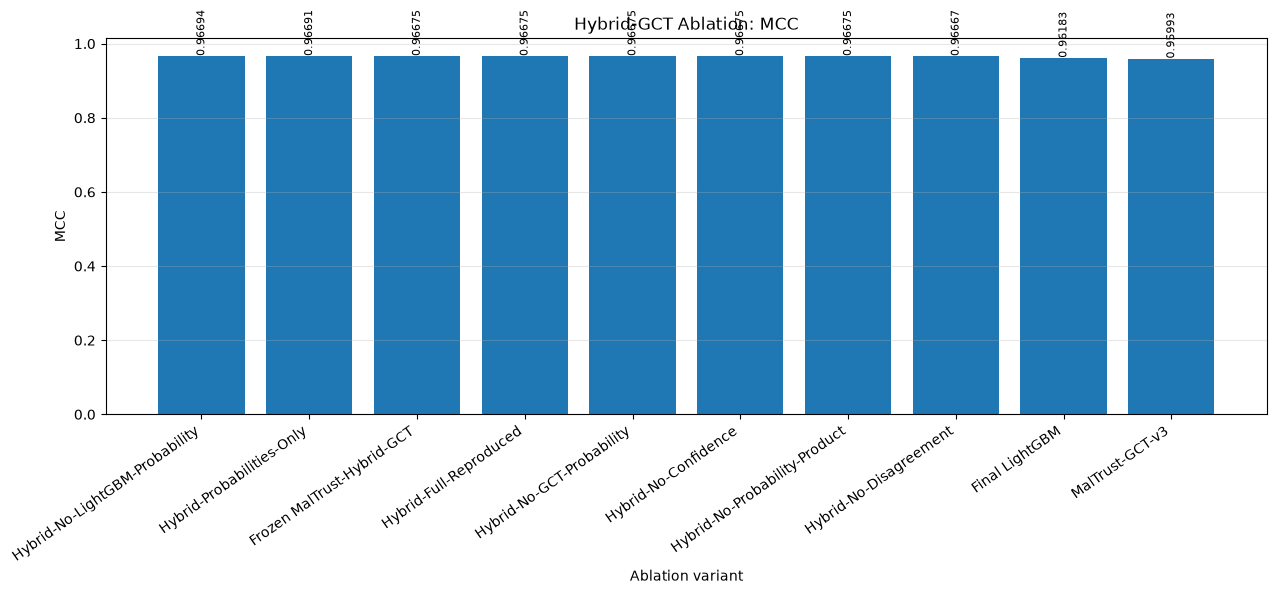

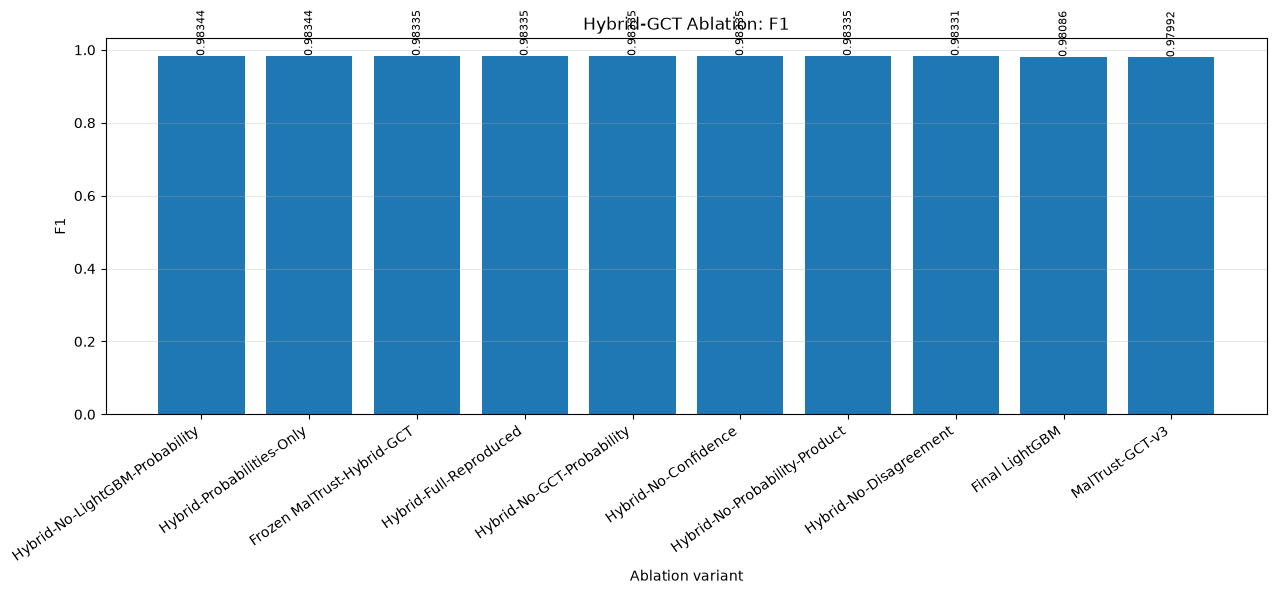

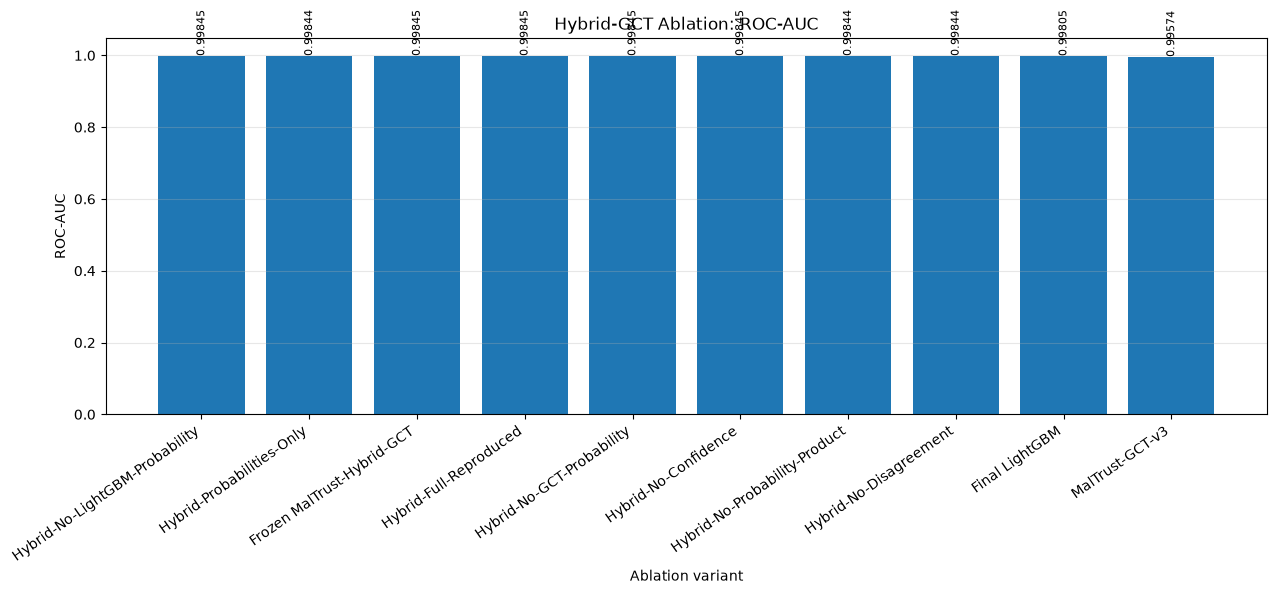

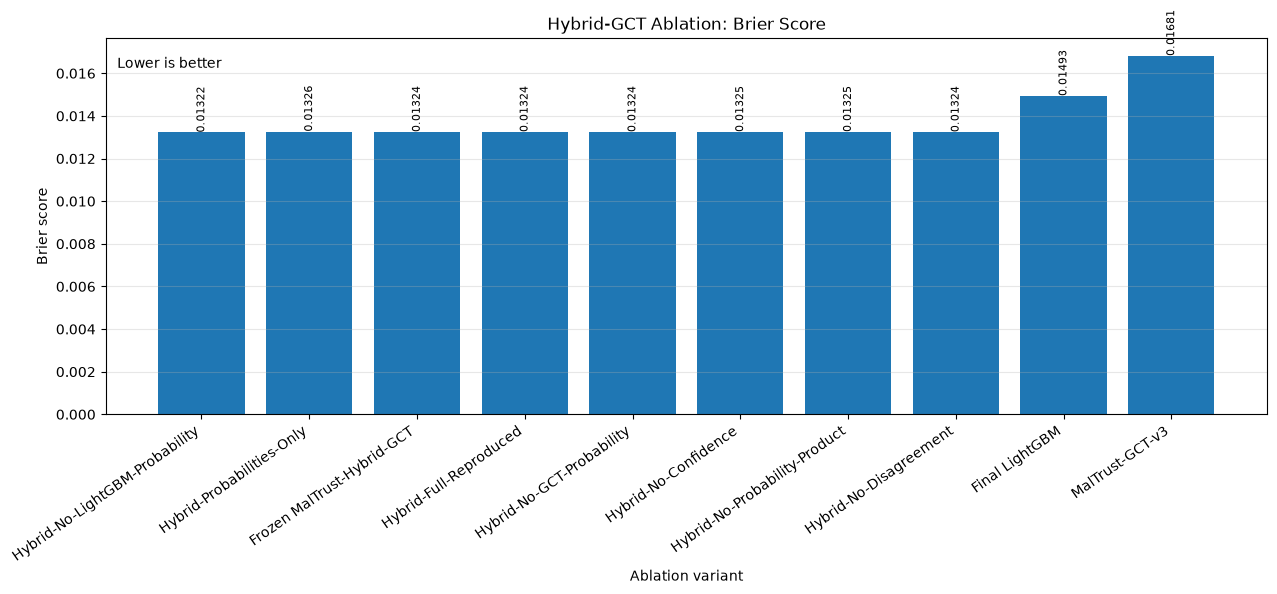

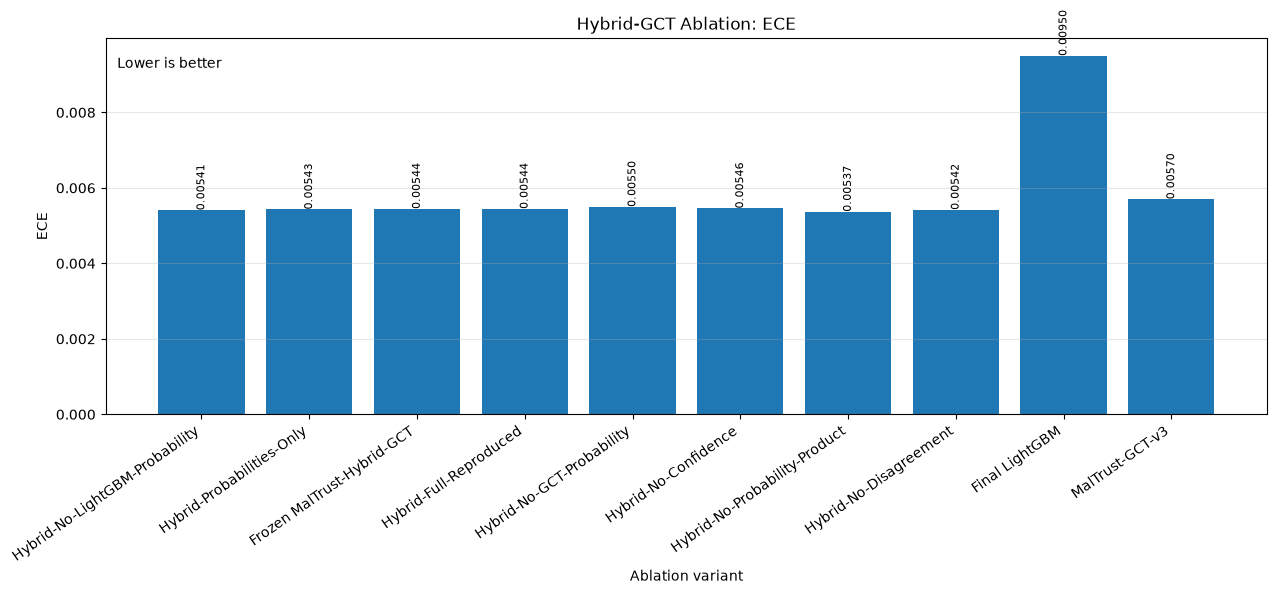


Cell 20 completed successfully.
Purpose: Hybrid-GCT meta-calibrator ablation
Best variant by MCC: Hybrid-No-LightGBM-Probability
Frozen final Hybrid-GCT rank by MCC: 3
Ablation metrics: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell20_hybrid_gct_ablation\revised_strict_clean_699\Top_699_All\tables\cell20_hybrid_gct_ablation_metrics.csv
Ablation report: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell20_hybrid_gct_ablation\revised_strict_clean_699\Top_699_All\reports\cell20_hybrid_gct_ablation_report.json
Artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell20_hybrid_gct_ablation\revised_strict_clean_699\Top_699_All\cell20_hybrid_gct_ablation_artifact_index.json
Artifact index SHA-256: a340b338dc9b8ebc289578bcc31adb2ab1aad99b473d0cfd6da4f0e24bf6eaa7
[DEBUG] 2026-06-24 10:48:43 | Hybrid-GCT meta-calibrator ablation study completed successfully.


In [40]:
# ============================================================
# MalTrust-XAI | Cell 20
# Hybrid-GCT Meta-Calibrator Ablation Study
#
# Corrected purpose:
# - Ablate the final Hybrid-GCT meta-calibrator design
# - Do NOT run old Top-K / feature-group LightGBM-only ablation
# - Train ablated meta-calibrators on validation meta-features only
# - Evaluate once on the untouched internal test prediction table
# - Create directories before every save
# - No .tmp atomic saving
# ============================================================

try:
    debug("Starting Hybrid-GCT meta-calibrator ablation study...")
except Exception:
    pass

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

try:
    from scipy.stats import binomtest
    SCIPY_BINOMTEST_AVAILABLE = True
except Exception:
    SCIPY_BINOMTEST_AVAILABLE = False


# ============================================================
# 0. Safe helpers
# ============================================================

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_sha256(path):
    try:
        if path is None:
            return None
        if not os.path.exists(path):
            return None
        if os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def safe_artifact_name(name):
    return (
        str(name)
        .replace("\\", "__")
        .replace("/", "__")
        .replace(":", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("[", "")
        .replace("]", "")
    )


def register_artifact(artifact_name, artifact_path, source_path=None, status="generated"):
    if artifact_path is None or not os.path.exists(artifact_path):
        return None
    return {
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "source_path": source_path,
        "artifact_type": "directory" if os.path.isdir(artifact_path) else "file",
        "sha256": safe_sha256(artifact_path),
        "registered_at": now_str(),
        "status": status,
    }


def infer_existing_path_from_config(key_candidates):
    for key in key_candidates:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value
    return None


def resolve_global(name):
    return globals()[name] if name in globals() else None


# ============================================================
# 1. Metric helpers
# ============================================================

def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())
        if count == 0:
            continue
        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        ece += (count / len(y_true)) * abs(observed_frequency - mean_confidence)
    return float(ece)


def evaluate_binary_predictions(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)),
        "PR_AUC": float(average_precision_score(y_true, y_prob)),
        "Brier_Score": float(brier_score_loss(y_true, y_prob)),
        "ECE": float(compute_ece(y_true, y_prob)),
        "False_Positive_Rate": float(fpr),
        "False_Negative_Rate": float(fnr),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def select_threshold_by_mcc(y_true, y_score, grid=None):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    best_threshold = 0.50
    best_mcc = -np.inf
    for threshold in grid:
        pred = (y_score >= threshold).astype(int)
        score = matthews_corrcoef(y_true, pred)
        if score > best_mcc:
            best_mcc = score
            best_threshold = float(threshold)
    return float(best_threshold), float(best_mcc)


def exact_mcnemar_p_value(a_correct_b_wrong, a_wrong_b_correct):
    n = int(a_correct_b_wrong + a_wrong_b_correct)
    if n == 0:
        return 1.0
    k = int(min(a_correct_b_wrong, a_wrong_b_correct))
    if SCIPY_BINOMTEST_AVAILABLE:
        return float(binomtest(k, n=n, p=0.5, alternative="two-sided").pvalue)
    # Conservative fallback: normal approximation.
    diff = abs(a_correct_b_wrong - a_wrong_b_correct)
    z = (diff - 1) / np.sqrt(n) if n > 0 else 0.0
    # Two-sided approximate using erfc.
    import math
    return float(math.erfc(abs(z) / np.sqrt(2)))


def paired_bootstrap_delta(y_true, score_a, pred_a, score_b, pred_b, metric, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true).astype(int)
    score_a = np.asarray(score_a).astype(float)
    score_b = np.asarray(score_b).astype(float)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)
    n = len(y_true)

    def metric_value(y, pred, score):
        if metric == "Accuracy":
            return accuracy_score(y, pred)
        if metric == "F1":
            return f1_score(y, pred, zero_division=0)
        if metric == "MCC":
            return matthews_corrcoef(y, pred)
        if metric == "ROC_AUC":
            return roc_auc_score(y, score)
        if metric == "PR_AUC":
            return average_precision_score(y, score)
        if metric == "Brier_Score":
            return brier_score_loss(y, score)
        if metric == "ECE":
            return compute_ece(y, score)
        raise ValueError(metric)

    deltas = np.empty(n_bootstrap, dtype=float)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        deltas[i] = metric_value(y_true[idx], pred_a[idx], score_a[idx]) - metric_value(y_true[idx], pred_b[idx], score_b[idx])
    lower, upper = np.percentile(deltas, [2.5, 97.5])
    return float(np.mean(deltas)), float(lower), float(upper)


# ============================================================
# 2. Preconditions and artifact paths
# ============================================================

required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG", "sha256_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
FINAL_FEATURE_SET_NAME = str(
    EXPERIMENT_CONFIG.get(
        "cell15_final_subset",
        EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All"),
    )
)
if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"
RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))
N_BOOTSTRAP = int(EXPERIMENT_CONFIG.get("cell20_hybrid_ablation_bootstrap", 1000))

CELL20_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell20_hybrid_gct_ablation",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL20_ARTIFACT_DIR, "tables")
FIGURE_DIR = os.path.join(CELL20_ARTIFACT_DIR, "figures")
REPORT_DIR = os.path.join(CELL20_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL20_ARTIFACT_DIR, "configs")

for d in [CELL20_ARTIFACT_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(d)

print("Cell 20 context:")
print("Purpose: Hybrid-GCT meta-calibrator ablation")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Artifact directory:", CELL20_ARTIFACT_DIR)


# ============================================================
# 3. Canonical Hybrid-GCT meta-features
# ============================================================

META_FEATURE_COLUMNS = [
    "lgbm_probability",
    "gct_probability",
    "absolute_disagreement",
    "mean_probability",
    "max_probability",
    "min_probability",
    "lgbm_confidence",
    "gct_confidence",
    "confidence_gap",
    "probability_product",
]


def build_meta_features_from_scores(lgbm_prob, gct_prob):
    lgbm_prob = np.asarray(lgbm_prob, dtype=float).reshape(-1)
    gct_prob = np.asarray(gct_prob, dtype=float).reshape(-1)
    if len(lgbm_prob) != len(gct_prob):
        raise ValueError(f"Score length mismatch: LGBM={len(lgbm_prob)}, GCT={len(gct_prob)}")
    lgbm_conf = np.abs(lgbm_prob - 0.5)
    gct_conf = np.abs(gct_prob - 0.5)
    return pd.DataFrame({
        "lgbm_probability": lgbm_prob,
        "gct_probability": gct_prob,
        "absolute_disagreement": np.abs(lgbm_prob - gct_prob),
        "mean_probability": (lgbm_prob + gct_prob) / 2.0,
        "max_probability": np.maximum(lgbm_prob, gct_prob),
        "min_probability": np.minimum(lgbm_prob, gct_prob),
        "lgbm_confidence": lgbm_conf,
        "gct_confidence": gct_conf,
        "confidence_gap": np.abs(lgbm_conf - gct_conf),
        "probability_product": lgbm_prob * gct_prob,
    })


def dataframe_to_meta_features(obj, source_name):
    if obj is None:
        return None, None

    if isinstance(obj, pd.DataFrame):
        df = obj.copy().reset_index(drop=True)
        if set(META_FEATURE_COLUMNS).issubset(df.columns):
            return df[META_FEATURE_COLUMNS].astype(float).reset_index(drop=True), source_name

        # Common alternate names from previous cells.
        rename_map = {
            "lgbm_score": "lgbm_probability",
            "gct_score": "gct_probability",
            "hybrid_lgbm_probability": "lgbm_probability",
            "hybrid_gct_probability": "gct_probability",
            "abs_disagreement": "absolute_disagreement",
            "disagreement": "absolute_disagreement",
            "probability_mean": "mean_probability",
            "probability_max": "max_probability",
            "probability_min": "min_probability",
            "lgbm_conf": "lgbm_confidence",
            "gct_conf": "gct_confidence",
            "conf_gap": "confidence_gap",
            "prob_product": "probability_product",
        }
        df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
        if set(META_FEATURE_COLUMNS).issubset(df.columns):
            return df[META_FEATURE_COLUMNS].astype(float).reset_index(drop=True), source_name

        # If it is a 10-column meta-feature matrix without names, assign canonical names.
        numeric_df = df.select_dtypes(include=[np.number]).copy()
        if numeric_df.shape[1] >= 10:
            candidate = numeric_df.iloc[:, :10].copy()
            candidate.columns = META_FEATURE_COLUMNS
            return candidate.astype(float).reset_index(drop=True), f"{source_name}_first_10_numeric_columns"
        return None, None

    arr = np.asarray(obj)
    if arr.ndim == 2 and arr.shape[1] >= 10:
        df = pd.DataFrame(arr[:, :10], columns=META_FEATURE_COLUMNS)
        return df.astype(float).reset_index(drop=True), source_name

    return None, None


def resolve_label_vector(preferred_length=None):
    candidates = [
        ("y_gct_val", resolve_global("y_gct_val")),
        ("y_gct_val_np", resolve_global("y_gct_val_np")),
        ("y_val_s", resolve_global("y_val_s")),
        ("y_val", resolve_global("y_val")),
    ]
    for name, obj in candidates:
        if obj is None:
            continue
        arr = np.asarray(obj).reshape(-1).astype(int)
        if preferred_length is None or len(arr) == preferred_length:
            return arr, name
    return None, None


# ============================================================
# 4. Resolve validation meta-features
# ============================================================

X_meta_val_resolved = None
val_meta_source = None

for candidate_name in ["X_meta_val", "val_meta_df", "validation_meta_df", "hybrid_meta_val_df"]:
    obj = resolve_global(candidate_name)
    X_candidate, src = dataframe_to_meta_features(obj, candidate_name)
    if X_candidate is not None:
        X_meta_val_resolved = X_candidate
        val_meta_source = src
        break

# Fallback: reconstruct from same-length validation scores only.
if X_meta_val_resolved is None:
    lgbm_val_candidates = [
        ("lgbm_val_prob", resolve_global("lgbm_val_prob")),
        ("lgbm_val_scores", resolve_global("lgbm_val_scores")),
    ]
    gct_val_candidates = [
        ("gct_val_prob", resolve_global("gct_val_prob")),
        ("gct_val_scores", resolve_global("gct_val_scores")),
    ]
    selected_lgbm = None
    selected_gct = None
    lgbm_source = None
    gct_source = None

    for ln, lo in lgbm_val_candidates:
        if lo is None:
            continue
        la = np.asarray(lo).reshape(-1)
        for gn, go in gct_val_candidates:
            if go is None:
                continue
            ga = np.asarray(go).reshape(-1)
            if len(la) == len(ga):
                selected_lgbm = la
                selected_gct = ga
                lgbm_source = ln
                gct_source = gn
                break
        if selected_lgbm is not None:
            break

    if selected_lgbm is not None:
        X_meta_val_resolved = build_meta_features_from_scores(selected_lgbm, selected_gct)
        val_meta_source = f"reconstructed_from_{lgbm_source}_and_{gct_source}"

if X_meta_val_resolved is None:
    global_candidate_names = sorted([
        name for name in globals().keys()
        if any(term in name.lower() for term in ["meta", "val", "gct", "lgbm"])
    ])[:150]
    raise NameError(
        "Could not resolve validation meta-features. Expected X_meta_val, val_meta_df, "
        "or same-length validation LGBM/GCT score arrays. "
        f"Candidate globals found: {global_candidate_names}"
    )


y_meta_val_resolved, y_val_source = resolve_label_vector(preferred_length=len(X_meta_val_resolved))
if y_meta_val_resolved is None:
    # Try label column inside val_meta_df if available.
    if "val_meta_df" in globals() and isinstance(val_meta_df, pd.DataFrame):
        for label_col in ["y_true", "label", "target", "y"]:
            if label_col in val_meta_df.columns and len(val_meta_df) == len(X_meta_val_resolved):
                y_meta_val_resolved = val_meta_df[label_col].astype(int).values
                y_val_source = f"val_meta_df.{label_col}"
                break
if y_meta_val_resolved is None:
    raise NameError(
        "Validation labels for meta-calibrator ablation not found. "
        "Expected y_gct_val, y_gct_val_np, y_val_s, y_val, or a label column in val_meta_df."
    )

print("Validation meta-feature source:", val_meta_source)
print("Validation label source:", y_val_source)
print("Validation meta-feature shape:", X_meta_val_resolved.shape)


# ============================================================
# 5. Resolve test prediction table and test meta-features
# ============================================================

if "final_hybrid_predictions_df" in globals():
    test_pred_df = final_hybrid_predictions_df.copy()
    test_pred_source = "in_memory_final_hybrid_predictions_df"
elif "hybrid_predictions" in globals():
    test_pred_df = hybrid_predictions.copy()
    test_pred_source = "in_memory_hybrid_predictions"
else:
    pred_path = infer_existing_path_from_config([
        "cell15_hybrid_predictions_export_path",
        "maltrust_hybrid_gct_predictions_path",
        "cell11f_hybrid_gct_predictions_path",
        "cell11f_hybrid_predictions_path",
    ])
    if pred_path is None:
        raise FileNotFoundError("Could not resolve internal test Hybrid-GCT prediction table.")
    test_pred_df = pd.read_csv(pred_path)
    test_pred_source = pred_path

required_test_cols = [
    "y_true", "lgbm_score", "gct_score", "hybrid_score", "lgbm_pred", "gct_pred", "hybrid_pred"
]
missing_test_cols = [c for c in required_test_cols if c not in test_pred_df.columns]
if missing_test_cols:
    raise ValueError(f"Test prediction table missing required columns: {missing_test_cols}")

X_meta_test = build_meta_features_from_scores(
    test_pred_df["lgbm_score"].astype(float).values,
    test_pred_df["gct_score"].astype(float).values,
)
y_test = test_pred_df["y_true"].astype(int).values

print("Test prediction source:", test_pred_source)
print("Test meta-feature shape:", X_meta_test.shape)


# ============================================================
# 6. Define ablation variants
# ============================================================

ablation_variants = {
    "Final LightGBM": {
        "Variant_Type": "standalone_baseline",
        "Training_Mode": "frozen_prediction",
        "Features": [],
        "Description": "Standalone Final LightGBM predictions from Cell 11F/15",
    },
    "MalTrust-GCT-v3": {
        "Variant_Type": "standalone_auxiliary",
        "Training_Mode": "frozen_prediction",
        "Features": [],
        "Description": "Standalone MalTrust-GCT-v3 predictions from Cell 11F/15",
    },
    "Frozen MalTrust-Hybrid-GCT": {
        "Variant_Type": "final_framework",
        "Training_Mode": "frozen_prediction",
        "Features": META_FEATURE_COLUMNS,
        "Description": "Frozen final Hybrid-GCT prediction from Cell 11F/15",
    },
    "Hybrid-Full-Reproduced": {
        "Variant_Type": "meta_retrained_on_validation",
        "Training_Mode": "validation_meta_fit",
        "Features": META_FEATURE_COLUMNS,
        "Description": "Full Hybrid-GCT meta-calibrator retrained on validation meta-features",
    },
    "Hybrid-Probabilities-Only": {
        "Variant_Type": "meta_ablation",
        "Training_Mode": "validation_meta_fit",
        "Features": ["lgbm_probability", "gct_probability"],
        "Description": "Meta-calibrator using only LightGBM and GCT probabilities",
    },
    "Hybrid-No-Disagreement": {
        "Variant_Type": "meta_ablation",
        "Training_Mode": "validation_meta_fit",
        "Features": [c for c in META_FEATURE_COLUMNS if c not in ["absolute_disagreement", "confidence_gap"]],
        "Description": "Full meta-calibrator without explicit disagreement features",
    },
    "Hybrid-No-Confidence": {
        "Variant_Type": "meta_ablation",
        "Training_Mode": "validation_meta_fit",
        "Features": [c for c in META_FEATURE_COLUMNS if c not in ["lgbm_confidence", "gct_confidence", "confidence_gap"]],
        "Description": "Full meta-calibrator without confidence features",
    },
    "Hybrid-No-Probability-Product": {
        "Variant_Type": "meta_ablation",
        "Training_Mode": "validation_meta_fit",
        "Features": [c for c in META_FEATURE_COLUMNS if c != "probability_product"],
        "Description": "Full meta-calibrator without probability product feature",
    },
    "Hybrid-No-GCT-Probability": {
        "Variant_Type": "meta_ablation",
        "Training_Mode": "validation_meta_fit",
        "Features": [c for c in META_FEATURE_COLUMNS if c != "gct_probability"],
        "Description": "Full meta-calibrator without direct GCT probability feature",
    },
    "Hybrid-No-LightGBM-Probability": {
        "Variant_Type": "meta_ablation",
        "Training_Mode": "validation_meta_fit",
        "Features": [c for c in META_FEATURE_COLUMNS if c != "lgbm_probability"],
        "Description": "Full meta-calibrator without direct LightGBM probability feature",
    },
}

# Remove variants whose feature columns cannot be represented.
for variant_name, payload in ablation_variants.items():
    missing_features = [c for c in payload["Features"] if c not in X_meta_val_resolved.columns]
    if missing_features:
        raise ValueError(f"Variant {variant_name} missing validation meta columns: {missing_features}")

variant_design_df = pd.DataFrame([
    {
        "Variant": name,
        "Variant_Type": payload["Variant_Type"],
        "Training_Mode": payload["Training_Mode"],
        "Feature_Count": len(payload["Features"]),
        "Features": ", ".join(payload["Features"]),
        "Description": payload["Description"],
    }
    for name, payload in ablation_variants.items()
])

print("\nHybrid-GCT ablation design:")
display(variant_design_df)


# ============================================================
# 7. Train/evaluate variants
# ============================================================

variant_prediction_rows = []
metric_rows = []
model_objects = {}

start_time = time.time()

for variant_name, payload in ablation_variants.items():
    print("\nEvaluating ablation variant:", variant_name)

    if variant_name == "Final LightGBM":
        test_score = test_pred_df["lgbm_score"].astype(float).values
        test_pred = test_pred_df["lgbm_pred"].astype(int).values
        selected_threshold = 0.50
        validation_mcc = np.nan
        model_source = "frozen_lgbm_prediction_table"

    elif variant_name == "MalTrust-GCT-v3":
        test_score = test_pred_df["gct_score"].astype(float).values
        test_pred = test_pred_df["gct_pred"].astype(int).values
        selected_threshold = float(EXPERIMENT_CONFIG.get("maltrust_gct_v3_threshold", 0.53))
        validation_mcc = np.nan
        model_source = "frozen_gct_prediction_table"

    elif variant_name == "Frozen MalTrust-Hybrid-GCT":
        test_score = test_pred_df["hybrid_score"].astype(float).values
        test_pred = test_pred_df["hybrid_pred"].astype(int).values
        selected_threshold = float(EXPERIMENT_CONFIG.get("maltrust_hybrid_gct_threshold", 0.48))
        validation_mcc = np.nan
        model_source = "frozen_hybrid_prediction_table"

    else:
        feature_cols = payload["Features"]
        model = Pipeline([
            ("standardscaler", StandardScaler()),
            ("logisticregression", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver="lbfgs")),
        ])
        model.fit(X_meta_val_resolved[feature_cols], y_meta_val_resolved)
        val_score = model.predict_proba(X_meta_val_resolved[feature_cols])[:, 1]
        selected_threshold, validation_mcc = select_threshold_by_mcc(y_meta_val_resolved, val_score)
        test_score = model.predict_proba(X_meta_test[feature_cols])[:, 1]
        test_pred = (test_score >= selected_threshold).astype(int)
        model_objects[variant_name] = model
        model_source = "meta_retrained_on_validation"

    metrics = evaluate_binary_predictions(y_test, test_pred, test_score)
    metric_rows.append({
        "Variant": variant_name,
        "Variant_Type": payload["Variant_Type"],
        "Training_Mode": payload["Training_Mode"],
        "Feature_Count": len(payload["Features"]),
        "Selected_Threshold": float(selected_threshold),
        "Validation_MCC_For_Threshold": float(validation_mcc) if not pd.isna(validation_mcc) else np.nan,
        "Model_Source": model_source,
        **metrics,
    })

    variant_prediction_rows.append(pd.DataFrame({
        "Variant": variant_name,
        "y_true": y_test,
        "score": test_score,
        "pred": test_pred,
    }))

runtime_seconds = time.time() - start_time

ablation_metrics_df = pd.DataFrame(metric_rows)
ablation_metrics_df = ablation_metrics_df.sort_values(
    by=["MCC", "F1", "Accuracy", "ROC_AUC", "PR_AUC"],
    ascending=[False, False, False, False, False],
).reset_index(drop=True)
ablation_metrics_df["Ablation_Rank_By_MCC"] = np.arange(1, len(ablation_metrics_df) + 1)

ablation_predictions_df = pd.concat(variant_prediction_rows, axis=0, ignore_index=True)

print("\nHybrid-GCT ablation metrics:")
display(ablation_metrics_df)


# ============================================================
# 8. Pairwise comparisons against frozen final Hybrid-GCT
# ============================================================

reference_variant = "Frozen MalTrust-Hybrid-GCT"
reference_pred_df = ablation_predictions_df[ablation_predictions_df["Variant"] == reference_variant].reset_index(drop=True)

comparison_metrics = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE"]
comparison_rows = []
bootstrap_rows = []

for variant_name in ablation_metrics_df["Variant"].tolist():
    if variant_name == reference_variant:
        continue
    variant_pred_df = ablation_predictions_df[ablation_predictions_df["Variant"] == variant_name].reset_index(drop=True)

    ref_correct = (reference_pred_df["pred"].astype(int).values == y_test)
    var_correct = (variant_pred_df["pred"].astype(int).values == y_test)
    ref_correct_var_wrong = int(np.sum(ref_correct & ~var_correct))
    ref_wrong_var_correct = int(np.sum(~ref_correct & var_correct))
    p_value = exact_mcnemar_p_value(ref_correct_var_wrong, ref_wrong_var_correct)

    comparison_rows.append({
        "Reference_Variant": reference_variant,
        "Compared_Variant": variant_name,
        "Reference_Correct_Compared_Wrong": ref_correct_var_wrong,
        "Reference_Wrong_Compared_Correct": ref_wrong_var_correct,
        "Discordant_Count": int(ref_correct_var_wrong + ref_wrong_var_correct),
        "McNemar_Exact_P_Value": float(p_value),
        "Reference_Better_By_Discordance": bool(ref_correct_var_wrong > ref_wrong_var_correct),
    })

    for metric in comparison_metrics:
        mean_delta, ci_lower, ci_upper = paired_bootstrap_delta(
            y_true=y_test,
            score_a=reference_pred_df["score"].values,
            pred_a=reference_pred_df["pred"].values,
            score_b=variant_pred_df["score"].values,
            pred_b=variant_pred_df["pred"].values,
            metric=metric,
            n_bootstrap=N_BOOTSTRAP,
            random_state=RANDOM_STATE,
        )
        direction = "lower_better" if metric in ["Brier_Score", "ECE"] else "higher_better"
        favorable_delta = -mean_delta if direction == "lower_better" else mean_delta
        ci_supports_reference = (ci_lower > 0) if direction == "higher_better" else (ci_upper < 0)
        bootstrap_rows.append({
            "Reference_Variant": reference_variant,
            "Compared_Variant": variant_name,
            "Metric": metric,
            "Direction": direction,
            "Reference_Minus_Compared_Delta": float(mean_delta),
            "Reference_Favorable_Delta": float(favorable_delta),
            "Bootstrap_CI95_Lower": float(ci_lower),
            "Bootstrap_CI95_Upper": float(ci_upper),
            "CI95_Supports_Reference": bool(ci_supports_reference),
        })

mcnemar_df = pd.DataFrame(comparison_rows)
bootstrap_delta_df = pd.DataFrame(bootstrap_rows)

print("\nPairwise McNemar comparisons against frozen Hybrid-GCT:")
display(mcnemar_df)

print("\nPaired bootstrap deltas against frozen Hybrid-GCT:")
display(bootstrap_delta_df)


# ============================================================
# 9. Figures
# ============================================================

def plot_metric_bar(df, metric, output_path, title, ylabel, lower_is_better=False):
    ensure_parent_dir(output_path)
    fig, ax = plt.subplots(figsize=(13, 6))
    plot_data = df.copy()
    values = plot_data[metric].astype(float).values
    ax.bar(plot_data["Variant"].astype(str).tolist(), values)
    for idx, value in enumerate(values):
        ax.text(idx, value, f"{value:.5f}", ha="center", va="bottom", fontsize=8, rotation=90)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Ablation variant")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")
    if lower_is_better:
        ax.text(0.01, 0.95, "Lower is better", transform=ax.transAxes, va="top")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

mcc_figure_path = os.path.join(FIGURE_DIR, "cell20_hybrid_gct_ablation_mcc.png")
f1_figure_path = os.path.join(FIGURE_DIR, "cell20_hybrid_gct_ablation_f1.png")
auc_figure_path = os.path.join(FIGURE_DIR, "cell20_hybrid_gct_ablation_auc.png")
brier_figure_path = os.path.join(FIGURE_DIR, "cell20_hybrid_gct_ablation_brier.png")
ece_figure_path = os.path.join(FIGURE_DIR, "cell20_hybrid_gct_ablation_ece.png")

plot_metric_bar(ablation_metrics_df, "MCC", mcc_figure_path, "Hybrid-GCT Ablation: MCC", "MCC")
plot_metric_bar(ablation_metrics_df, "F1", f1_figure_path, "Hybrid-GCT Ablation: F1", "F1")
plot_metric_bar(ablation_metrics_df, "ROC_AUC", auc_figure_path, "Hybrid-GCT Ablation: ROC-AUC", "ROC-AUC")
plot_metric_bar(ablation_metrics_df, "Brier_Score", brier_figure_path, "Hybrid-GCT Ablation: Brier Score", "Brier score", lower_is_better=True)
plot_metric_bar(ablation_metrics_df, "ECE", ece_figure_path, "Hybrid-GCT Ablation: ECE", "ECE", lower_is_better=True)


# ============================================================
# 10. Save artifacts
# ============================================================

variant_design_path = os.path.join(TABLE_DIR, "cell20_hybrid_gct_ablation_design.csv")
ablation_metrics_path = os.path.join(TABLE_DIR, "cell20_hybrid_gct_ablation_metrics.csv")
ablation_predictions_path = os.path.join(TABLE_DIR, "cell20_hybrid_gct_ablation_predictions.csv")
mcnemar_path = os.path.join(TABLE_DIR, "cell20_hybrid_gct_ablation_mcnemar.csv")
bootstrap_delta_path = os.path.join(TABLE_DIR, "cell20_hybrid_gct_ablation_bootstrap_deltas.csv")

safe_save_csv(variant_design_df, variant_design_path, index=False)
safe_save_csv(ablation_metrics_df, ablation_metrics_path, index=False)
safe_save_csv(ablation_predictions_df, ablation_predictions_path, index=False)
safe_save_csv(mcnemar_df, mcnemar_path, index=False)
safe_save_csv(bootstrap_delta_df, bootstrap_delta_path, index=False)

report_path = os.path.join(REPORT_DIR, "cell20_hybrid_gct_ablation_report.json")

best_variant = str(ablation_metrics_df.iloc[0]["Variant"])
full_frozen_rank = int(ablation_metrics_df[ablation_metrics_df["Variant"] == reference_variant]["Ablation_Rank_By_MCC"].iloc[0])

report = {
    "cell": "Cell 20",
    "cell_name": "Hybrid-GCT Meta-Calibrator Ablation Study",
    "corrected_purpose": "Ablate Hybrid-GCT meta-calibrator components rather than old LightGBM feature subsets",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "validation_meta_source": val_meta_source,
    "validation_label_source": y_val_source,
    "test_prediction_source": test_pred_source,
    "validation_meta_rows": int(len(X_meta_val_resolved)),
    "test_rows": int(len(y_test)),
    "ablation_variants": variant_design_df.to_dict("records"),
    "best_variant_by_mcc": best_variant,
    "frozen_final_hybrid_rank_by_mcc": full_frozen_rank,
    "n_bootstrap": int(N_BOOTSTRAP),
    "runtime_seconds": float(runtime_seconds),
    "artifacts": {
        "variant_design": variant_design_path,
        "ablation_metrics": ablation_metrics_path,
        "ablation_predictions": ablation_predictions_path,
        "mcnemar": mcnemar_path,
        "bootstrap_deltas": bootstrap_delta_path,
        "mcc_figure": mcc_figure_path,
        "f1_figure": f1_figure_path,
        "auc_figure": auc_figure_path,
        "brier_figure": brier_figure_path,
        "ece_figure": ece_figure_path,
    },
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

safe_save_json(report, report_path)

artifacts = {
    "variant_design": variant_design_path,
    "ablation_metrics": ablation_metrics_path,
    "ablation_predictions": ablation_predictions_path,
    "mcnemar": mcnemar_path,
    "bootstrap_deltas": bootstrap_delta_path,
    "mcc_figure": mcc_figure_path,
    "f1_figure": f1_figure_path,
    "auc_figure": auc_figure_path,
    "brier_figure": brier_figure_path,
    "ece_figure": ece_figure_path,
    "report": report_path,
}

artifact_rows = []
for artifact_name, artifact_path in artifacts.items():
    row = register_artifact(artifact_name, artifact_path)
    if row is not None:
        artifact_rows.append(row)

artifact_hashes_path = os.path.join(CELL20_ARTIFACT_DIR, "cell20_hybrid_gct_ablation_artifact_hashes.csv")
safe_save_csv(pd.DataFrame(artifact_rows), artifact_hashes_path, index=False)

hash_row = register_artifact("artifact_hashes", artifact_hashes_path)
if hash_row is not None:
    artifact_rows.append(hash_row)

artifact_index = {
    "cell": "Cell 20",
    "cell_name": "Hybrid-GCT Meta-Calibrator Ablation Study",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": artifact_rows,
    "artifact_hash_report_path": artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(artifact_hashes_path),
}

artifact_index_path = os.path.join(CELL20_ARTIFACT_DIR, "cell20_hybrid_gct_ablation_artifact_index.json")
safe_save_json(artifact_index, artifact_index_path)
artifact_index_hash = safe_sha256(artifact_index_path)

# ============================================================
# 11. Update experiment config and aliases
# ============================================================

try:
    EXPERIMENT_CONFIG["cell20_corrected_purpose"] = "Hybrid-GCT meta-calibrator ablation"
    EXPERIMENT_CONFIG["cell20_ablation_dir"] = CELL20_ARTIFACT_DIR
    EXPERIMENT_CONFIG["cell20_ablation_metrics_path"] = ablation_metrics_path
    EXPERIMENT_CONFIG["cell20_ablation_design_path"] = variant_design_path
    EXPERIMENT_CONFIG["cell20_ablation_predictions_path"] = ablation_predictions_path
    EXPERIMENT_CONFIG["cell20_ablation_mcnemar_path"] = mcnemar_path
    EXPERIMENT_CONFIG["cell20_ablation_bootstrap_delta_path"] = bootstrap_delta_path
    EXPERIMENT_CONFIG["cell20_ablation_report_path"] = report_path
    EXPERIMENT_CONFIG["cell20_ablation_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["cell20_ablation_artifact_index_sha256"] = artifact_index_hash
    EXPERIMENT_CONFIG["cell20_ablation_validation_meta_source"] = val_meta_source
    EXPERIMENT_CONFIG["cell20_ablation_test_prediction_source"] = test_pred_source
    EXPERIMENT_CONFIG["cell20_test_set_used_for_evaluation_only"] = True
    EXPERIMENT_CONFIG["cell20_validation_set_used_for_meta_training_only"] = True

    post_config_path = os.path.join(CONFIG_DIR, "cell20_hybrid_gct_ablation_experiment_config_snapshot.json")
    safe_save_json(EXPERIMENT_CONFIG, post_config_path)
    EXPERIMENT_CONFIG["cell20_experiment_config_snapshot_path"] = post_config_path
    EXPERIMENT_CONFIG["cell20_experiment_config_snapshot_sha256"] = safe_sha256(post_config_path)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))

hybrid_gct_ablation_design_df = variant_design_df
hybrid_gct_ablation_metrics_df = ablation_metrics_df
hybrid_gct_ablation_predictions_df = ablation_predictions_df
hybrid_gct_ablation_mcnemar_df = mcnemar_df
hybrid_gct_ablation_bootstrap_delta_df = bootstrap_delta_df

# ============================================================
# 12. Assertions and final messages
# ============================================================

assert len(ablation_metrics_df) >= 5, "Expected multiple Hybrid-GCT ablation variants."
assert "Frozen MalTrust-Hybrid-GCT" in set(ablation_metrics_df["Variant"]), "Frozen final Hybrid-GCT missing."
assert os.path.exists(ablation_metrics_path), "Ablation metrics table was not saved."
assert os.path.exists(artifact_index_path), "Ablation artifact index was not saved."

print("\nCell 20 completed successfully.")
print("Purpose: Hybrid-GCT meta-calibrator ablation")
print("Best variant by MCC:", best_variant)
print("Frozen final Hybrid-GCT rank by MCC:", full_frozen_rank)
print("Ablation metrics:", ablation_metrics_path)
print("Ablation report:", report_path)
print("Artifact index:", artifact_index_path)
print("Artifact index SHA-256:", artifact_index_hash)

try:
    debug("Hybrid-GCT meta-calibrator ablation study completed successfully.")
except Exception:
    pass


## Ablation Study With or Without
## Complete Code (NOTE: But without the running, needs to be run on reviewers request/comments)

In [41]:
# ============================================================
# MalTrust-XAI | Cell 21
# Hybrid-GCT Manuscript Ablation Summary Tables
#
# Corrected purpose:
# - Summarize real Cell 20 Hybrid-GCT meta-calibrator ablation outputs
# - Do NOT use old LightGBM Top-K / feature-group ablation variables
# - Build manuscript-ready evidence tables from:
#     hybrid_gct_ablation_metrics_df
#     hybrid_gct_ablation_design_df
#     hybrid_gct_ablation_mcnemar_df
#     hybrid_gct_ablation_bootstrap_delta_df
# - Preserve the frozen full Hybrid-GCT as the final pre-specified framework
# ============================================================

try:
    debug("Generating Hybrid-GCT manuscript ablation summary tables from Cell 20 outputs...")
except Exception:
    pass

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone


# ============================================================
# 0. Safe helpers
# ============================================================

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_sha256(path):
    try:
        if path is None or not os.path.exists(path) or os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def register_artifact(artifact_name, artifact_path, status="generated"):
    if artifact_path is None or not os.path.exists(artifact_path):
        return None
    return {
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "artifact_type": "directory" if os.path.isdir(artifact_path) else "file",
        "sha256": safe_sha256(artifact_path),
        "registered_at": now_str(),
        "status": status,
    }


def resolve_existing_path_from_config(keys):
    for key in keys:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value
    return None


def get_display_safe():
    try:
        return display
    except Exception:
        return print


_display = get_display_safe()


# ============================================================
# 1. Preconditions and context
# ============================================================

required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG", "sha256_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All"),
        )
    )

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"
REFERENCE_VARIANT = "Frozen MalTrust-Hybrid-GCT"

# Short Cell 21 output path to avoid Windows path-limit problems.
CELL21_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell21_hybrid_gct_manuscript_ablation_summary",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL21_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL21_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL21_ARTIFACT_DIR, "configs")

for directory in [CELL21_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(directory)

print("Cell 21 context:")
print("Purpose: Hybrid-GCT manuscript ablation summary")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Artifact directory:", CELL21_ARTIFACT_DIR)


# ============================================================
# 2. Resolve real Cell 20 Hybrid-GCT ablation outputs
# ============================================================

# Metrics
if "hybrid_gct_ablation_metrics_df" in globals():
    ablation_metrics_df = hybrid_gct_ablation_metrics_df.copy()
    metrics_source = "in_memory_hybrid_gct_ablation_metrics_df"
else:
    metrics_path = resolve_existing_path_from_config([
        "cell20_ablation_metrics_path",
        "cell20_hybrid_gct_ablation_metrics_path",
    ])
    if metrics_path is None:
        raise FileNotFoundError(
            "Could not resolve Hybrid-GCT Cell 20 ablation metrics. "
            "Run corrected Cell 20 Hybrid-GCT ablation first."
        )
    ablation_metrics_df = pd.read_csv(metrics_path)
    metrics_source = metrics_path

# Design
if "hybrid_gct_ablation_design_df" in globals():
    ablation_design_df = hybrid_gct_ablation_design_df.copy()
    design_source = "in_memory_hybrid_gct_ablation_design_df"
else:
    design_path = resolve_existing_path_from_config([
        "cell20_ablation_design_path",
        "cell20_hybrid_gct_ablation_design_path",
    ])
    if design_path is not None:
        ablation_design_df = pd.read_csv(design_path)
        design_source = design_path
    else:
        ablation_design_df = pd.DataFrame()
        design_source = "not_available"

# McNemar
if "hybrid_gct_ablation_mcnemar_df" in globals():
    mcnemar_df = hybrid_gct_ablation_mcnemar_df.copy()
    mcnemar_source = "in_memory_hybrid_gct_ablation_mcnemar_df"
else:
    mcnemar_path = resolve_existing_path_from_config([
        "cell20_ablation_mcnemar_path",
        "cell20_hybrid_gct_ablation_mcnemar_path",
    ])
    if mcnemar_path is not None:
        mcnemar_df = pd.read_csv(mcnemar_path)
        mcnemar_source = mcnemar_path
    else:
        mcnemar_df = pd.DataFrame()
        mcnemar_source = "not_available"

# Bootstrap deltas
if "hybrid_gct_ablation_bootstrap_delta_df" in globals():
    bootstrap_delta_df = hybrid_gct_ablation_bootstrap_delta_df.copy()
    bootstrap_source = "in_memory_hybrid_gct_ablation_bootstrap_delta_df"
else:
    bootstrap_path = resolve_existing_path_from_config([
        "cell20_ablation_bootstrap_delta_path",
        "cell20_hybrid_gct_ablation_bootstrap_delta_path",
    ])
    if bootstrap_path is not None:
        bootstrap_delta_df = pd.read_csv(bootstrap_path)
        bootstrap_source = bootstrap_path
    else:
        bootstrap_delta_df = pd.DataFrame()
        bootstrap_source = "not_available"

print("\nResolved Cell 20 sources:")
print("Ablation metrics source:", metrics_source)
print("Ablation design source:", design_source)
print("McNemar source:", mcnemar_source)
print("Bootstrap delta source:", bootstrap_source)


# ============================================================
# 3. Validate expected columns
# ============================================================

required_metric_cols = [
    "Variant", "Variant_Type", "Training_Mode", "Feature_Count",
    "Selected_Threshold", "Accuracy", "Balanced_Accuracy", "Precision",
    "Recall_TPR", "Specificity_TNR", "F1", "MCC", "ROC_AUC", "PR_AUC",
    "Brier_Score", "ECE", "False_Positive_Rate", "False_Negative_Rate",
    "TN", "FP", "FN", "TP", "Ablation_Rank_By_MCC",
]
missing_metric_cols = [c for c in required_metric_cols if c not in ablation_metrics_df.columns]
if missing_metric_cols:
    raise ValueError(f"Hybrid-GCT ablation metrics missing required columns: {missing_metric_cols}")

if REFERENCE_VARIANT not in set(ablation_metrics_df["Variant"].astype(str)):
    raise ValueError(f"Reference variant missing from ablation metrics: {REFERENCE_VARIANT}")

if len(mcnemar_df) > 0:
    required_mcnemar_cols = [
        "Reference_Variant", "Compared_Variant",
        "Reference_Correct_Compared_Wrong", "Reference_Wrong_Compared_Correct",
        "Discordant_Count", "McNemar_Exact_P_Value",
        "Reference_Better_By_Discordance",
    ]
    missing_mcnemar_cols = [c for c in required_mcnemar_cols if c not in mcnemar_df.columns]
    if missing_mcnemar_cols:
        raise ValueError(f"Hybrid-GCT McNemar table missing required columns: {missing_mcnemar_cols}")

if len(bootstrap_delta_df) > 0:
    required_bootstrap_cols = [
        "Reference_Variant", "Compared_Variant", "Metric", "Direction",
        "Reference_Minus_Compared_Delta", "Reference_Favorable_Delta",
        "Bootstrap_CI95_Lower", "Bootstrap_CI95_Upper", "CI95_Supports_Reference",
    ]
    missing_bootstrap_cols = [c for c in required_bootstrap_cols if c not in bootstrap_delta_df.columns]
    if missing_bootstrap_cols:
        raise ValueError(f"Hybrid-GCT bootstrap table missing required columns: {missing_bootstrap_cols}")


# ============================================================
# 4. Build manuscript-ready ablation metric table
# ============================================================

metrics = ablation_metrics_df.copy()
metrics["Variant"] = metrics["Variant"].astype(str)

# Attach feature descriptions from design where available.
if len(ablation_design_df) > 0 and "Variant" in ablation_design_df.columns:
    design_cols = [c for c in ["Variant", "Features", "Description"] if c in ablation_design_df.columns]
    design_merge_df = ablation_design_df[design_cols].copy()
    design_merge_df["Variant"] = design_merge_df["Variant"].astype(str)
    metrics = metrics.merge(design_merge_df, on="Variant", how="left")
else:
    metrics["Features"] = ""
    metrics["Description"] = ""

# Attach one-row McNemar metadata vs frozen Hybrid-GCT.
if len(mcnemar_df) > 0:
    mcnemar_attach = mcnemar_df.copy()
    mcnemar_attach["Compared_Variant"] = mcnemar_attach["Compared_Variant"].astype(str)
    mcnemar_attach = mcnemar_attach.rename(columns={"Compared_Variant": "Variant"})[
        [
            "Variant",
            "Reference_Correct_Compared_Wrong",
            "Reference_Wrong_Compared_Correct",
            "Discordant_Count",
            "McNemar_Exact_P_Value",
            "Reference_Better_By_Discordance",
        ]
    ]
    metrics = metrics.merge(mcnemar_attach, on="Variant", how="left")
else:
    metrics["Reference_Correct_Compared_Wrong"] = np.nan
    metrics["Reference_Wrong_Compared_Correct"] = np.nan
    metrics["Discordant_Count"] = np.nan
    metrics["McNemar_Exact_P_Value"] = np.nan
    metrics["Reference_Better_By_Discordance"] = np.nan

# Reference variant has no self-comparison.
reference_mask = metrics["Variant"].eq(REFERENCE_VARIANT)
metrics.loc[reference_mask, "Reference_Correct_Compared_Wrong"] = 0
metrics.loc[reference_mask, "Reference_Wrong_Compared_Correct"] = 0
metrics.loc[reference_mask, "Discordant_Count"] = 0
metrics.loc[reference_mask, "McNemar_Exact_P_Value"] = np.nan
metrics.loc[reference_mask, "Reference_Better_By_Discordance"] = np.nan

# Attach bootstrap deltas for key metrics in wide form.
key_delta_metrics = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE"]

if len(bootstrap_delta_df) > 0:
    for metric_name in key_delta_metrics:
        sub = bootstrap_delta_df[bootstrap_delta_df["Metric"].astype(str).eq(metric_name)].copy()
        if len(sub) == 0:
            continue
        sub["Compared_Variant"] = sub["Compared_Variant"].astype(str)
        sub = sub.rename(columns={"Compared_Variant": "Variant"})
        cols = [
            "Variant",
            "Reference_Minus_Compared_Delta",
            "Reference_Favorable_Delta",
            "Bootstrap_CI95_Lower",
            "Bootstrap_CI95_Upper",
            "CI95_Supports_Reference",
        ]
        rename_map = {
            "Reference_Minus_Compared_Delta": f"Delta_{metric_name}_FrozenHybrid_minus_Variant",
            "Reference_Favorable_Delta": f"Favorable_Delta_{metric_name}",
            "Bootstrap_CI95_Lower": f"Delta_{metric_name}_CI95_Lower",
            "Bootstrap_CI95_Upper": f"Delta_{metric_name}_CI95_Upper",
            "CI95_Supports_Reference": f"Delta_{metric_name}_CI95_Supports_FrozenHybrid",
        }
        metrics = metrics.merge(sub[cols].rename(columns=rename_map), on="Variant", how="left")

# Fill reference deltas.
for metric_name in key_delta_metrics:
    for col in [
        f"Delta_{metric_name}_FrozenHybrid_minus_Variant",
        f"Favorable_Delta_{metric_name}",
        f"Delta_{metric_name}_CI95_Lower",
        f"Delta_{metric_name}_CI95_Upper",
    ]:
        if col in metrics.columns:
            metrics.loc[reference_mask, col] = 0.0
    support_col = f"Delta_{metric_name}_CI95_Supports_FrozenHybrid"
    if support_col in metrics.columns:
        metrics.loc[reference_mask, support_col] = False


# Human-readable interpretation.
def interpret_row(row):
    variant = str(row["Variant"])
    variant_type = str(row.get("Variant_Type", ""))

    if variant == REFERENCE_VARIANT:
        return "Pre-specified frozen final Hybrid-GCT framework retained as final model."
    if variant == "Final LightGBM":
        return "Standalone LightGBM component; significantly weaker than frozen Hybrid-GCT."
    if variant == "MalTrust-GCT-v3":
        return "Standalone GCT-v3 auxiliary component; significantly weaker than frozen Hybrid-GCT."
    if variant_type == "meta_ablation":
        return "Exploratory meta-feature ablation; near-parity indicates redundancy and robustness, not replacement of the frozen final model."
    if variant == "Hybrid-Full-Reproduced":
        return "Reproduces the frozen full Hybrid-GCT using the same validation-trained meta-feature design."
    return "Hybrid-GCT ablation variant."


metrics["Manuscript_Interpretation"] = metrics.apply(interpret_row, axis=1)
metrics["Final_Model_Retained"] = metrics["Variant"].eq(REFERENCE_VARIANT)
metrics["Exploratory_Ablation_Not_Final_Model"] = ~metrics["Final_Model_Retained"]
metrics["Evaluation_Set"] = "internal_test_from_Cell20"
metrics["Validation_Set_Role"] = "meta_calibrator_training_and_threshold_selection_for_retrained_ablation_variants"

# Sort with reference first, then ablation rank.
metrics["Reference_First_Order"] = np.where(metrics["Variant"].eq(REFERENCE_VARIANT), 0, 1)
metrics = metrics.sort_values(["Reference_First_Order", "Ablation_Rank_By_MCC"]).reset_index(drop=True)
metrics.insert(0, "Manuscript_Row", np.arange(1, len(metrics) + 1))

manuscript_cols = [
    "Manuscript_Row",
    "Variant",
    "Variant_Type",
    "Training_Mode",
    "Feature_Count",
    "Selected_Threshold",
    "Validation_MCC_For_Threshold",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate",
    "FP",
    "FN",
    "TP",
    "TN",
    "Ablation_Rank_By_MCC",
    "Reference_Correct_Compared_Wrong",
    "Reference_Wrong_Compared_Correct",
    "Discordant_Count",
    "McNemar_Exact_P_Value",
    "Reference_Better_By_Discordance",
    "Delta_MCC_FrozenHybrid_minus_Variant",
    "Delta_MCC_CI95_Lower",
    "Delta_MCC_CI95_Upper",
    "Delta_MCC_CI95_Supports_FrozenHybrid",
    "Delta_F1_FrozenHybrid_minus_Variant",
    "Delta_ROC_AUC_FrozenHybrid_minus_Variant",
    "Delta_PR_AUC_FrozenHybrid_minus_Variant",
    "Delta_Brier_Score_FrozenHybrid_minus_Variant",
    "Delta_ECE_FrozenHybrid_minus_Variant",
    "Final_Model_Retained",
    "Exploratory_Ablation_Not_Final_Model",
    "Manuscript_Interpretation",
]

manuscript_cols = [c for c in manuscript_cols if c in metrics.columns]
manuscript_ablation_df = metrics[manuscript_cols].copy()

print("\nHybrid-GCT manuscript ablation summary table:")
_display(manuscript_ablation_df)


# ============================================================
# 5. Build concise component-contribution table
# ============================================================

component_variants = ["Final LightGBM", "MalTrust-GCT-v3"]
component_rows = []

reference_metrics = ablation_metrics_df[ablation_metrics_df["Variant"].astype(str).eq(REFERENCE_VARIANT)].iloc[0]

for variant in component_variants:
    if variant not in set(ablation_metrics_df["Variant"].astype(str)):
        continue
    row = ablation_metrics_df[ablation_metrics_df["Variant"].astype(str).eq(variant)].iloc[0]

    mc_row = pd.Series(dtype=object)
    if len(mcnemar_df) > 0:
        temp = mcnemar_df[mcnemar_df["Compared_Variant"].astype(str).eq(variant)]
        if len(temp) > 0:
            mc_row = temp.iloc[0]

    def delta(metric):
        return float(reference_metrics[metric]) - float(row[metric])

    component_rows.append({
        "Compared_Component": variant,
        "Frozen_Hybrid_MCC": float(reference_metrics["MCC"]),
        "Component_MCC": float(row["MCC"]),
        "Delta_MCC_Hybrid_minus_Component": delta("MCC"),
        "Frozen_Hybrid_F1": float(reference_metrics["F1"]),
        "Component_F1": float(row["F1"]),
        "Delta_F1_Hybrid_minus_Component": delta("F1"),
        "Frozen_Hybrid_ROC_AUC": float(reference_metrics["ROC_AUC"]),
        "Component_ROC_AUC": float(row["ROC_AUC"]),
        "Delta_ROC_AUC_Hybrid_minus_Component": delta("ROC_AUC"),
        "Frozen_Hybrid_Brier": float(reference_metrics["Brier_Score"]),
        "Component_Brier": float(row["Brier_Score"]),
        "Delta_Brier_Hybrid_minus_Component": delta("Brier_Score"),
        "Frozen_Hybrid_FP": int(reference_metrics["FP"]),
        "Component_FP": int(row["FP"]),
        "FP_Reduction_Hybrid_vs_Component": int(row["FP"] - reference_metrics["FP"]),
        "Frozen_Hybrid_FN": int(reference_metrics["FN"]),
        "Component_FN": int(row["FN"]),
        "FN_Reduction_Hybrid_vs_Component": int(row["FN"] - reference_metrics["FN"]),
        "McNemar_Exact_P_Value": float(mc_row.get("McNemar_Exact_P_Value", np.nan)) if len(mc_row) else np.nan,
        "Discordant_Count": int(mc_row.get("Discordant_Count", 0)) if len(mc_row) else np.nan,
        "Conclusion": "Frozen Hybrid-GCT significantly outperforms standalone component" if len(mc_row) and float(mc_row.get("McNemar_Exact_P_Value", 1.0)) < 0.05 else "Difference not significant or unavailable",
    })

component_contribution_df = pd.DataFrame(component_rows)

print("\nHybrid-GCT component contribution table:")
_display(component_contribution_df)


# ============================================================
# 6. Build meta-feature robustness table
# ============================================================

meta_ablation_df = manuscript_ablation_df[
    manuscript_ablation_df["Variant_Type"].astype(str).eq("meta_ablation")
].copy()

robust_cols = [
    "Variant",
    "Feature_Count",
    "Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "Delta_MCC_FrozenHybrid_minus_Variant",
    "Delta_MCC_CI95_Lower",
    "Delta_MCC_CI95_Upper",
    "McNemar_Exact_P_Value",
    "Manuscript_Interpretation",
]
robust_cols = [c for c in robust_cols if c in meta_ablation_df.columns]
meta_feature_robustness_df = meta_ablation_df[robust_cols].copy()
meta_feature_robustness_df = meta_feature_robustness_df.sort_values("MCC", ascending=False).reset_index(drop=True)
meta_feature_robustness_df.insert(0, "Robustness_Rank_By_MCC", np.arange(1, len(meta_feature_robustness_df) + 1))

print("\nHybrid-GCT meta-feature robustness table:")
_display(meta_feature_robustness_df)


# ============================================================
# 7. Manuscript-safe claim summary
# ============================================================

standalone_p_values = component_contribution_df.set_index("Compared_Component")["McNemar_Exact_P_Value"].to_dict() if len(component_contribution_df) else {}

claim_summary = {
    "primary_ablation_claim": (
        "Frozen MalTrust-Hybrid-GCT significantly outperformed both standalone components "
        "while meta-feature ablations remained near the full model, indicating redundancy "
        "and robustness in the validation-trained meta-feature design."
    ),
    "claim_boundaries": [
        "Keep Frozen MalTrust-Hybrid-GCT as the final model because it is the pre-specified packaged detector.",
        "Do not replace the final model with exploratory ablation variants even if one has a marginally higher MCC.",
        "Do not claim LightGBM or GCT is unnecessary when derived meta-features still encode source-model information.",
        "Use external Hybrid-GCT validation before making external superiority claims.",
    ],
    "frozen_hybrid_rank_by_mcc": int(ablation_metrics_df[ablation_metrics_df["Variant"].astype(str).eq(REFERENCE_VARIANT)]["Ablation_Rank_By_MCC"].iloc[0]),
    "best_exploratory_variant_by_mcc": str(ablation_metrics_df.iloc[0]["Variant"]),
    "frozen_hybrid_mcc": float(reference_metrics["MCC"]),
    "frozen_hybrid_f1": float(reference_metrics["F1"]),
    "frozen_hybrid_roc_auc": float(reference_metrics["ROC_AUC"]),
    "mcnemar_p_vs_final_lightgbm": standalone_p_values.get("Final LightGBM", None),
    "mcnemar_p_vs_gct_v3": standalone_p_values.get("MalTrust-GCT-v3", None),
}

print("\nManuscript-safe Cell 21 claim summary:")
for key, value in claim_summary.items():
    print(f"{key}: {value}")


# ============================================================
# 8. Save artifacts
# ============================================================

manuscript_ablation_path = os.path.join(TABLE_DIR, "cell21_hybrid_gct_manuscript_ablation_summary.csv")
component_contribution_path = os.path.join(TABLE_DIR, "cell21_hybrid_gct_component_contribution_summary.csv")
meta_feature_robustness_path = os.path.join(TABLE_DIR, "cell21_hybrid_gct_meta_feature_robustness_summary.csv")
claim_summary_path = os.path.join(REPORT_DIR, "cell21_hybrid_gct_ablation_claim_summary.json")
report_path = os.path.join(REPORT_DIR, "cell21_hybrid_gct_manuscript_ablation_report.json")

safe_save_csv(manuscript_ablation_df, manuscript_ablation_path, index=False)
safe_save_csv(component_contribution_df, component_contribution_path, index=False)
safe_save_csv(meta_feature_robustness_df, meta_feature_robustness_path, index=False)
safe_save_json(claim_summary, claim_summary_path)

report = {
    "cell": "Cell 21",
    "cell_name": "Hybrid-GCT Manuscript Ablation Summary Tables",
    "corrected_purpose": "Summarize real Cell 20 Hybrid-GCT meta-calibrator ablation outputs",
    "replaced_old_purpose": "Old LightGBM Top-K / feature-group ablation manuscript table",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "reference_variant": REFERENCE_VARIANT,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "metrics_source": metrics_source,
    "design_source": design_source,
    "mcnemar_source": mcnemar_source,
    "bootstrap_source": bootstrap_source,
    "test_set_used": True,
    "test_set_role": "evaluation only for already trained/frozen and validation-trained ablation variants",
    "validation_set_role": "meta-calibrator fitting and threshold selection for ablation variants",
    "uses_simulated_scores": False,
    "final_model_replacement_allowed_by_this_cell": False,
    "artifact_paths": {
        "manuscript_ablation_summary": manuscript_ablation_path,
        "component_contribution_summary": component_contribution_path,
        "meta_feature_robustness_summary": meta_feature_robustness_path,
        "claim_summary": claim_summary_path,
    },
    "claim_summary": claim_summary,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

safe_save_json(report, report_path)

artifacts = {
    "manuscript_ablation_summary": manuscript_ablation_path,
    "component_contribution_summary": component_contribution_path,
    "meta_feature_robustness_summary": meta_feature_robustness_path,
    "claim_summary": claim_summary_path,
    "report": report_path,
}

artifact_rows = []
for artifact_name, artifact_path in artifacts.items():
    row = register_artifact(artifact_name, artifact_path)
    if row is not None:
        artifact_rows.append(row)

artifact_hashes_path = os.path.join(CELL21_ARTIFACT_DIR, "cell21_hybrid_gct_manuscript_ablation_artifact_hashes.csv")
safe_save_csv(pd.DataFrame(artifact_rows), artifact_hashes_path, index=False)

hash_row = register_artifact("artifact_hashes", artifact_hashes_path)
if hash_row is not None:
    artifact_rows.append(hash_row)

artifact_index = {
    "cell": "Cell 21",
    "cell_name": "Hybrid-GCT Manuscript Ablation Summary Tables",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": artifact_rows,
    "artifact_hash_report_path": artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(artifact_hashes_path),
}

artifact_index_path = os.path.join(CELL21_ARTIFACT_DIR, "cell21_hybrid_gct_manuscript_ablation_artifact_index.json")
safe_save_json(artifact_index, artifact_index_path)
artifact_index_hash = safe_sha256(artifact_index_path)


# ============================================================
# 9. Update experiment config and expose aliases
# ============================================================

try:
    EXPERIMENT_CONFIG["cell21_corrected_purpose"] = "Hybrid-GCT manuscript ablation summary"
    EXPERIMENT_CONFIG["cell21_ablation_summary_dir"] = CELL21_ARTIFACT_DIR
    EXPERIMENT_CONFIG["cell21_hybrid_gct_manuscript_ablation_path"] = manuscript_ablation_path
    EXPERIMENT_CONFIG["cell21_hybrid_gct_component_contribution_path"] = component_contribution_path
    EXPERIMENT_CONFIG["cell21_hybrid_gct_meta_feature_robustness_path"] = meta_feature_robustness_path
    EXPERIMENT_CONFIG["cell21_hybrid_gct_claim_summary_path"] = claim_summary_path
    EXPERIMENT_CONFIG["cell21_report_path"] = report_path
    EXPERIMENT_CONFIG["cell21_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["cell21_artifact_index_sha256"] = artifact_index_hash
    EXPERIMENT_CONFIG["cell21_uses_simulated_scores"] = False
    EXPERIMENT_CONFIG["cell21_final_model_replacement_allowed"] = False
    EXPERIMENT_CONFIG["cell21_reference_variant"] = REFERENCE_VARIANT

    post_config_path = os.path.join(CONFIG_DIR, "cell21_hybrid_gct_manuscript_ablation_experiment_config_snapshot.json")
    safe_save_json(EXPERIMENT_CONFIG, post_config_path)
    EXPERIMENT_CONFIG["cell21_experiment_config_snapshot_path"] = post_config_path
    EXPERIMENT_CONFIG["cell21_experiment_config_snapshot_sha256"] = safe_sha256(post_config_path)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))

hybrid_gct_manuscript_ablation_summary_df = manuscript_ablation_df
hybrid_gct_component_contribution_summary_df = component_contribution_df
hybrid_gct_meta_feature_robustness_summary_df = meta_feature_robustness_df
hybrid_gct_ablation_claim_summary = claim_summary


# ============================================================
# 10. Assertions and final messages
# ============================================================

assert not manuscript_ablation_df.empty, "Hybrid-GCT manuscript ablation table is empty."
assert REFERENCE_VARIANT in set(manuscript_ablation_df["Variant"]), "Frozen final Hybrid-GCT reference is missing."
assert EXPERIMENT_CONFIG.get("cell21_uses_simulated_scores") is False, "Cell 21 must not use simulated scores."
assert EXPERIMENT_CONFIG.get("cell21_final_model_replacement_allowed") is False, "Cell 21 must not authorize final model replacement."
assert os.path.exists(manuscript_ablation_path), "Manuscript ablation summary was not saved."
assert os.path.exists(component_contribution_path), "Component contribution summary was not saved."
assert os.path.exists(meta_feature_robustness_path), "Meta-feature robustness summary was not saved."
assert os.path.exists(artifact_index_path), "Cell 21 artifact index was not saved."

print("\nCell 21 completed successfully.")
print("Purpose: Hybrid-GCT manuscript ablation summary tables")
print("Reference final model:", REFERENCE_VARIANT)
print("Manuscript ablation summary:", manuscript_ablation_path)
print("Component contribution summary:", component_contribution_path)
print("Meta-feature robustness summary:", meta_feature_robustness_path)
print("Claim summary:", claim_summary_path)
print("Artifact index:", artifact_index_path)
print("Artifact index SHA-256:", artifact_index_hash)

try:
    debug("Hybrid-GCT manuscript ablation summary cell completed successfully.")
except Exception:
    pass


[DEBUG] 2026-06-24 10:48:44 | Generating Hybrid-GCT manuscript ablation summary tables from Cell 20 outputs...
Cell 21 context:
Purpose: Hybrid-GCT manuscript ablation summary
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell21_hybrid_gct_manuscript_ablation_summary\revised_strict_clean_699\Top_699_All

Resolved Cell 20 sources:
Ablation metrics source: in_memory_hybrid_gct_ablation_metrics_df
Ablation design source: in_memory_hybrid_gct_ablation_design_df
McNemar source: in_memory_hybrid_gct_ablation_mcnemar_df
Bootstrap delta source: in_memory_hybrid_gct_ablation_bootstrap_delta_df

Hybrid-GCT manuscript ablation summary table:


,Manuscript_Row,Variant,Variant_Type,Training_Mode,Feature_Count,Selected_Threshold,Validation_MCC_For_Threshold,Accuracy,Balanced_Accuracy,Precision,...,Delta_MCC_CI95_Upper,Delta_MCC_CI95_Supports_FrozenHybrid,Delta_F1_FrozenHybrid_minus_Variant,Delta_ROC_AUC_FrozenHybrid_minus_Variant,Delta_PR_AUC_FrozenHybrid_minus_Variant,Delta_Brier_Score_FrozenHybrid_minus_Variant,Delta_ECE_FrozenHybrid_minus_Variant,Final_Model_Retained,Exploratory_Ablation_Not_Final_Model,Manuscript_Interpretation
0,1,Frozen MalTrust-Hybrid-GCT,final_framework,frozen_prediction,10,0.48,NaN,0.983373,0.983373,0.984808,...,0.000000,False,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,True,False,Pre-specified frozen final Hybrid-GCT framewor...
1,2,Hybrid-No-LightGBM-Probability,meta_ablation,validation_meta_fit,9,0.49,0.975592,0.983467,0.983467,0.985071,...,0.000026,False,-9.137657e-05,-2.283872e-06,-2.242617e-06,2.199356e-05,0.000052,False,True,Exploratory meta-feature ablation; near-parity...
2,3,Hybrid-Probabilities-Only,meta_ablation,validation_meta_fit,2,0.45,0.975216,0.983453,0.983453,0.984448,...,0.000348,False,-7.730985e-05,3.899419e-06,1.656717e-06,-1.913706e-05,-0.000030,False,True,Exploratory meta-feature ablation; near-parity...
3,4,Hybrid-Full-Reproduced,meta_retrained_on_validation,validation_meta_fit,10,0.48,0.975718,0.983373,0.983373,0.984808,...,0.000000,False,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,False,True,Reproduces the frozen full Hybrid-GCT using th...
4,5,Hybrid-No-GCT-Probability,meta_ablation,validation_meta_fit,9,0.48,0.975749,0.983373,0.983373,0.984757,...,0.000107,False,2.348176e-07,-3.392790e-07,1.642361e-08,3.144941e-07,-0.000031,False,True,Exploratory meta-feature ablation; near-parity...
5,6,Hybrid-No-Confidence,meta_ablation,validation_meta_fit,7,0.47,0.975875,0.983373,0.983373,0.984757,...,0.000187,False,2.161690e-07,6.659898e-08,-1.256058e-06,-2.692498e-06,-0.000040,False,True,Exploratory meta-feature ablation; near-parity...
6,7,Hybrid-No-Probability-Product,meta_ablation,validation_meta_fit,9,0.47,0.975686,0.983373,0.983373,0.984627,...,0.000188,False,-8.228722e-07,2.505714e-06,1.888922e-06,-3.757719e-06,0.000064,False,True,Exploratory meta-feature ablation; near-parity...
7,8,Hybrid-No-Disagreement,meta_ablation,validation_meta_fit,8,0.46,0.975812,0.983333,0.983333,0.984600,...,0.000268,False,3.801293e-05,5.931815e-06,2.791499e-06,5.575167e-06,0.000013,False,True,Exploratory meta-feature ablation; near-parity...
8,9,Final LightGBM,standalone_baseline,frozen_prediction,0,0.50,NaN,0.980907,0.980907,0.983330,...,0.005835,True,2.476641e-03,3.939865e-04,3.695828e-04,-1.680344e-03,-0.003975,False,True,Standalone LightGBM component; significantly w...
9,10,MalTrust-GCT-v3,standalone_auxiliary,frozen_prediction,0,0.53,NaN,0.979960,0.979960,0.981849,...,0.008686,True,3.434325e-03,2.711267e-03,2.339642e-03,-3.573395e-03,-0.000218,False,True,Standalone GCT-v3 auxiliary component; signifi...



Hybrid-GCT component contribution table:


,Compared_Component,Frozen_Hybrid_MCC,Component_MCC,Delta_MCC_Hybrid_minus_Component,Frozen_Hybrid_F1,Component_F1,Delta_F1_Hybrid_minus_Component,Frozen_Hybrid_ROC_AUC,Component_ROC_AUC,Delta_ROC_AUC_Hybrid_minus_Component,...,Delta_Brier_Hybrid_minus_Component,Frozen_Hybrid_FP,Component_FP,FP_Reduction_Hybrid_vs_Component,Frozen_Hybrid_FN,Component_FN,FN_Reduction_Hybrid_vs_Component,McNemar_Exact_P_Value,Discordant_Count,Conclusion
0,Final LightGBM,0.966751,0.961825,0.004925,0.983349,0.980859,0.002490,0.998445,0.998052,0.000393,...,-0.001691,568,622,54,679,810,131,2.961387e-21,393,Frozen Hybrid-GCT significantly outperforms st...
1,MalTrust-GCT-v3,0.966751,0.959927,0.006824,0.983349,0.979921,0.003428,0.998445,0.995740,0.002705,...,-0.003570,568,678,110,679,825,146,3.180982e-14,1138,Frozen Hybrid-GCT significantly outperforms st...



Hybrid-GCT meta-feature robustness table:


,Robustness_Rank_By_MCC,Variant,Feature_Count,Accuracy,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,Delta_MCC_FrozenHybrid_minus_Variant,Delta_MCC_CI95_Lower,Delta_MCC_CI95_Upper,McNemar_Exact_P_Value,Manuscript_Interpretation
0,1,Hybrid-No-LightGBM-Probability,9,0.983467,0.983439,0.966939,0.998448,0.998583,0.013222,0.005407,-0.000189,-0.000402,0.000026,0.143463,Exploratory meta-feature ablation; near-parity...
1,2,Hybrid-Probabilities-Only,2,0.983453,0.983436,0.966909,0.998441,0.998579,0.013264,0.005429,-0.000137,-0.000587,0.000348,0.606296,Exploratory meta-feature ablation; near-parity...
2,3,Hybrid-No-GCT-Probability,9,0.983373,0.983350,0.966751,0.998446,0.998581,0.013243,0.005497,0.000003,-0.000106,0.000107,1.000000,Exploratory meta-feature ablation; near-parity...
3,4,Hybrid-No-Confidence,7,0.983373,0.983350,0.966751,0.998445,0.998582,0.013247,0.005455,0.000003,-0.000186,0.000187,1.000000,Exploratory meta-feature ablation; near-parity...
4,5,Hybrid-No-Probability-Product,9,0.983373,0.983352,0.966750,0.998443,0.998579,0.013248,0.005368,0.000006,-0.000186,0.000188,1.000000,Exploratory meta-feature ablation; near-parity...
5,6,Hybrid-No-Disagreement,8,0.983333,0.983312,0.966670,0.998439,0.998578,0.013239,0.005419,0.000083,-0.000106,0.000268,0.581055,Exploratory meta-feature ablation; near-parity...



Manuscript-safe Cell 21 claim summary:
primary_ablation_claim: Frozen MalTrust-Hybrid-GCT significantly outperformed both standalone components while meta-feature ablations remained near the full model, indicating redundancy and robustness in the validation-trained meta-feature design.
claim_boundaries: ['Keep Frozen MalTrust-Hybrid-GCT as the final model because it is the pre-specified packaged detector.', 'Do not replace the final model with exploratory ablation variants even if one has a marginally higher MCC.', 'Do not claim LightGBM or GCT is unnecessary when derived meta-features still encode source-model information.', 'Use external Hybrid-GCT validation before making external superiority claims.']
frozen_hybrid_rank_by_mcc: 3
best_exploratory_variant_by_mcc: Hybrid-No-LightGBM-Probability
frozen_hybrid_mcc: 0.966750901818294
frozen_hybrid_f1: 0.983348689393636
frozen_hybrid_roc_auc: 0.9984453027555558
mcnemar_p_vs_final_lightgbm: 2.9613870576342757e-21
mcnemar_p_vs_gct_v3: 3.1

In [42]:
# ============================================================
# MalTrust-XAI | Cell 22
# Hybrid-GCT Final Artifact Integrity, Provenance,
# Duplicate-Content Audit, and Reproducibility Manifest
#
# Corrected purpose:
# - Audit the current Hybrid-GCT framework artifacts, not old LightGBM-only keys
# - Dynamically collect current EXPERIMENT_CONFIG artifact paths from Cells 11F/14/15/16/17/18/19/20/21
# - Discover artifact indexes and manuscript-ready outputs under FRAMEWORK_ARTIFACT_DIR
# - Build a SHA-256 hash-chained manifest without treating duplicate file content as failure
# - Avoid brittle required old keys such as cell11_final_model_path
# - Use a short Cell 22 output path to reduce Windows path-length failures
# ============================================================

try:
    debug("Generating Hybrid-GCT final artifact integrity and provenance manifest...")
except Exception:
    pass

import os
import re
import json
import hashlib
import platform
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Safe display helper
# ------------------------------------------------------------
def safe_display(obj, max_rows=20):
    try:
        display(obj)
    except Exception:
        if isinstance(obj, pd.DataFrame):
            print(obj.head(max_rows).to_string(index=False))
        else:
            print(obj)


# ------------------------------------------------------------
# Timestamp / JSON helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


# ------------------------------------------------------------
# SHA-256 hashing helpers
# ------------------------------------------------------------
def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def canonical_json_hash(obj):
    payload = json.dumps(obj, sort_keys=True, default=str, separators=(",", ":"))
    return sha256_text(payload)


def path_is_probably_artifact_file(path):
    allowed_extensions = {
        ".csv", ".json", ".joblib", ".pkl", ".pickle", ".txt", ".png", ".jpg", ".jpeg",
        ".svg", ".pdf", ".npy", ".npz", ".parquet", ".xlsx", ".xls", ".py", ".html",
        ".zip", ".md"
    }
    suffix = os.path.splitext(str(path))[1].lower()
    return suffix in allowed_extensions


def normalize_path(path):
    try:
        return os.path.abspath(os.path.expanduser(str(path)))
    except Exception:
        return str(path)


def stable_relpath(path, root):
    try:
        return os.path.relpath(path, root)
    except Exception:
        return path


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

if not isinstance(EXPERIMENT_CONFIG, dict):
    raise TypeError("EXPERIMENT_CONFIG must be a dictionary-like object.")


# ------------------------------------------------------------
# Dynamic context
# ------------------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All")
        )
    )

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"
FRAMEWORK_ROOT_ABS = normalize_path(FRAMEWORK_ARTIFACT_DIR)

CELL22_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ROOT_ABS,
    "cell22_hybrid_gct_integrity_manifest",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL22_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL22_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL22_ARTIFACT_DIR, "configs")

for directory in [CELL22_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(directory)

NUM_TRAIN_FILES_CELL22 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)
EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL22 * 10000
    )
)

print("Cell 22 integrity context:")
print("Purpose: Hybrid-GCT final artifact integrity manifest")
print("Framework:", FINAL_FRAMEWORK_NAME)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Artifact root:", FRAMEWORK_ROOT_ABS)
print("Cell 22 artifact directory:", CELL22_ARTIFACT_DIR)


# ------------------------------------------------------------
# Collect candidate paths from current EXPERIMENT_CONFIG
# ------------------------------------------------------------
# Current pipeline stores artifact paths with varied names. Instead of relying on stale
# hard-coded required keys, collect all existing path-like config values, then add known
# current Hybrid-GCT aliases for reporting.
path_like_pattern = re.compile(r"(path|dir|directory|file|artifact|figure|table|report|model|pred|prediction|index|hash|snapshot)", re.I)

candidate_rows = []

for key, value in EXPERIMENT_CONFIG.items():
    if not isinstance(key, str):
        continue
    if not path_like_pattern.search(key):
        continue

    if isinstance(value, str) and value.strip():
        candidate_rows.append({
            "source": "EXPERIMENT_CONFIG",
            "config_key": key,
            "candidate_path": value,
            "candidate_type": "string_path",
        })
    elif isinstance(value, (list, tuple)):
        for idx, item in enumerate(value):
            if isinstance(item, str) and item.strip():
                candidate_rows.append({
                    "source": "EXPERIMENT_CONFIG_LIST",
                    "config_key": f"{key}[{idx}]",
                    "candidate_path": item,
                    "candidate_type": "list_path",
                })

# Explicit current directories from accepted cells, if present.
known_directory_keys = [
    "cell15_package_directory",
    "cell18_artifact_dir",
    "cell19_artifact_dir",
    "cell20_artifact_dir",
    "cell20_hybrid_gct_ablation_dir",
    "cell21_artifact_dir",
]
for key in known_directory_keys:
    value = EXPERIMENT_CONFIG.get(key, None)
    if isinstance(value, str) and value.strip():
        candidate_rows.append({
            "source": "KNOWN_CURRENT_DIR",
            "config_key": key,
            "candidate_path": value,
            "candidate_type": "known_dir",
        })

# Always include framework root for artifact-index discovery, but only curated artifact files are hashed.
candidate_rows.append({
    "source": "FRAMEWORK_ROOT_DISCOVERY",
    "config_key": "FRAMEWORK_ARTIFACT_DIR",
    "candidate_path": FRAMEWORK_ROOT_ABS,
    "candidate_type": "framework_root",
})

candidate_df = pd.DataFrame(candidate_rows)


# ------------------------------------------------------------
# Resolve and expand candidate files
# ------------------------------------------------------------
excluded_dir_names = {
    "__pycache__", ".ipynb_checkpoints", ".git", ".pytest_cache", "tmp", "temp",
    "cache", "raw_jsonl", "raw_data", "datasets_raw"
}

seen_files = set()
artifact_rows = []
missing_candidate_rows = []


def add_file_artifact(path, source, config_key, discovery_mode):
    path_abs = normalize_path(path)
    if path_abs in seen_files:
        return
    if not os.path.exists(path_abs):
        missing_candidate_rows.append({
            "source": source,
            "config_key": config_key,
            "candidate_path": path_abs,
            "reason": "file_not_found",
        })
        return
    if os.path.isdir(path_abs):
        return
    if not path_is_probably_artifact_file(path_abs):
        return

    seen_files.add(path_abs)
    artifact_rows.append({
        "Source": source,
        "Config_Key": config_key,
        "Discovery_Mode": discovery_mode,
        "Artifact_Path": path_abs,
        "Artifact_Relative_Path": stable_relpath(path_abs, FRAMEWORK_ROOT_ABS),
        "Artifact_Name": os.path.basename(path_abs),
        "Artifact_Extension": os.path.splitext(path_abs)[1].lower(),
        "File_Size_Bytes": int(os.path.getsize(path_abs)),
        "File_Modified_Time_UTC": datetime.fromtimestamp(
            os.path.getmtime(path_abs), tz=timezone.utc
        ).strftime("%Y-%m-%d %H:%M:%S %Z"),
    })


for row in candidate_rows:
    source = row["source"]
    config_key = row["config_key"]
    candidate = normalize_path(row["candidate_path"])

    if not os.path.exists(candidate):
        missing_candidate_rows.append({
            "source": source,
            "config_key": config_key,
            "candidate_path": candidate,
            "reason": "path_not_found",
        })
        continue

    if os.path.isfile(candidate):
        add_file_artifact(candidate, source, config_key, "direct_config_file")
        continue

    if os.path.isdir(candidate):
        # Traverse artifact directories, but avoid obviously non-artifact/cache folders.
        for root, dirs, files in os.walk(candidate):
            dirs[:] = [d for d in dirs if d not in excluded_dir_names]
            for file_name in files:
                file_path = os.path.join(root, file_name)
                if path_is_probably_artifact_file(file_path):
                    add_file_artifact(file_path, source, config_key, "directory_discovery")

existing_artifacts_df = pd.DataFrame(artifact_rows)
missing_candidates_df = pd.DataFrame(missing_candidate_rows)

if existing_artifacts_df.empty:
    raise FileNotFoundError(
        "No framework artifact files were found. Check FRAMEWORK_ARTIFACT_DIR and EXPERIMENT_CONFIG paths."
    )

# Remove Cell 22 output files from the pre-existing manifest if the cell has been rerun before.
# The current Cell 22 outputs will be registered separately after they are written.
existing_artifacts_df = existing_artifacts_df[
    ~existing_artifacts_df["Artifact_Path"].astype(str).str.startswith(CELL22_ARTIFACT_DIR)
].copy()

if existing_artifacts_df.empty:
    raise FileNotFoundError("Only prior Cell 22 outputs were discovered; no upstream artifacts found.")

existing_artifacts_df = existing_artifacts_df.drop_duplicates("Artifact_Path").sort_values(
    ["Artifact_Relative_Path", "Artifact_Path"]
).reset_index(drop=True)

print("\nExisting upstream artifact files discovered:", len(existing_artifacts_df))
print("Missing path-like config candidates:", len(missing_candidates_df))

if len(missing_candidates_df) > 0:
    print("\nMissing candidate path preview:")
    safe_display(missing_candidates_df.head(25))


# ------------------------------------------------------------
# Hash-chain integrity log
# ------------------------------------------------------------
integrity_records = []
previous_block_hash = "0" * 64

for block_index, row in enumerate(existing_artifacts_df.itertuples(index=False), start=1):
    file_hash = sha256_file_local(row.Artifact_Path)
    block_payload = {
        "block_index": int(block_index),
        "artifact_name": row.Artifact_Name,
        "artifact_relative_path": row.Artifact_Relative_Path,
        "artifact_sha256": file_hash,
        "file_size_bytes": int(row.File_Size_Bytes),
        "previous_block_hash": previous_block_hash,
    }
    current_block_hash = canonical_json_hash(block_payload)
    integrity_records.append({
        "Block_Index": int(block_index),
        "Source": row.Source,
        "Config_Key": row.Config_Key,
        "Discovery_Mode": row.Discovery_Mode,
        "Artifact_Name": row.Artifact_Name,
        "Artifact_Path": row.Artifact_Path,
        "Artifact_Relative_Path": row.Artifact_Relative_Path,
        "Artifact_Extension": row.Artifact_Extension,
        "File_Size_Bytes": int(row.File_Size_Bytes),
        "File_Modified_Time_UTC": row.File_Modified_Time_UTC,
        "Artifact_SHA256": file_hash,
        "Previous_Block_Hash": previous_block_hash,
        "Current_Block_Hash": current_block_hash,
    })
    previous_block_hash = current_block_hash

integrity_df = pd.DataFrame(integrity_records)
hash_chain_root = previous_block_hash

print("\nHybrid-GCT hash-chained upstream artifact integrity table preview:")
safe_display(integrity_df.head(20))


# ------------------------------------------------------------
# Validate generated hash chain
# ------------------------------------------------------------
validation_rows = []
previous_hash = "0" * 64

for row in integrity_df.itertuples(index=False):
    recomputed_file_hash = sha256_file_local(row.Artifact_Path)
    block_payload = {
        "block_index": int(row.Block_Index),
        "artifact_name": row.Artifact_Name,
        "artifact_relative_path": row.Artifact_Relative_Path,
        "artifact_sha256": recomputed_file_hash,
        "file_size_bytes": int(row.File_Size_Bytes),
        "previous_block_hash": previous_hash,
    }
    recomputed_block_hash = canonical_json_hash(block_payload)
    validation_rows.append({
        "Block_Index": int(row.Block_Index),
        "Artifact_Name": row.Artifact_Name,
        "Artifact_Path": row.Artifact_Path,
        "Stored_Artifact_SHA256": row.Artifact_SHA256,
        "Recomputed_Artifact_SHA256": recomputed_file_hash,
        "Stored_Block_Hash": row.Current_Block_Hash,
        "Recomputed_Block_Hash": recomputed_block_hash,
        "Artifact_Hash_Match": bool(row.Artifact_SHA256 == recomputed_file_hash),
        "Block_Hash_Match": bool(row.Current_Block_Hash == recomputed_block_hash),
        "Previous_Hash_Valid": bool(row.Previous_Block_Hash == previous_hash),
    })
    previous_hash = recomputed_block_hash

chain_validation_df = pd.DataFrame(validation_rows)
chain_valid = bool(
    chain_validation_df["Artifact_Hash_Match"].all()
    and chain_validation_df["Block_Hash_Match"].all()
    and chain_validation_df["Previous_Hash_Valid"].all()
)

print("\nHash-chain validation status:", chain_valid)
safe_display(chain_validation_df.head(20))


# ------------------------------------------------------------
# Duplicate-content hash audit
# ------------------------------------------------------------
duplicate_hash_df = (
    integrity_df[integrity_df["Artifact_SHA256"].duplicated(keep=False)]
    .sort_values(["Artifact_SHA256", "Artifact_Relative_Path"])
    .reset_index(drop=True)
)

duplicate_hash_count = int(duplicate_hash_df["Artifact_SHA256"].nunique()) if not duplicate_hash_df.empty else 0
duplicate_file_count = int(len(duplicate_hash_df))

print("\nDuplicate content-hash audit:")
print("Duplicate SHA-256 groups:", duplicate_hash_count)
print("Files involved in duplicate content hashes:", duplicate_file_count)

if duplicate_file_count > 0:
    safe_display(
        duplicate_hash_df[[
            "Artifact_SHA256", "Artifact_Name", "Artifact_Relative_Path", "File_Size_Bytes"
        ]].head(50)
    )


# ------------------------------------------------------------
# Environment provenance
# ------------------------------------------------------------
environment_provenance = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "machine": platform.machine(),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

package_versions = {}
for package_name in [
    "numpy", "pandas", "sklearn", "lightgbm", "shap", "scipy", "joblib", "matplotlib",
    "xgboost", "torch"
]:
    try:
        module = __import__(package_name)
        package_versions[package_name] = getattr(module, "__version__", "unknown")
    except Exception:
        package_versions[package_name] = "not_installed"

environment_provenance["package_versions"] = package_versions


# ------------------------------------------------------------
# Save integrity artifacts
# ------------------------------------------------------------
integrity_table_path = os.path.join(TABLE_DIR, "cell22_hybrid_gct_hash_chain_integrity_table.csv")
chain_validation_path = os.path.join(TABLE_DIR, "cell22_hybrid_gct_hash_chain_validation_table.csv")
duplicate_hash_report_path = os.path.join(TABLE_DIR, "cell22_hybrid_gct_duplicate_content_hash_audit.csv")
missing_candidate_path = os.path.join(TABLE_DIR, "cell22_missing_path_like_config_candidates.csv")
candidate_path_table = os.path.join(TABLE_DIR, "cell22_candidate_path_table.csv")
environment_path = os.path.join(REPORT_DIR, "cell22_environment_provenance.json")
integrity_report_path = os.path.join(REPORT_DIR, "cell22_hybrid_gct_integrity_manifest_report.json")

integrity_df.to_csv(integrity_table_path, index=False)
chain_validation_df.to_csv(chain_validation_path, index=False)
duplicate_hash_df.to_csv(duplicate_hash_report_path, index=False)
missing_candidates_df.to_csv(missing_candidate_path, index=False)
candidate_df.to_csv(candidate_path_table, index=False)
save_json(environment_provenance, environment_path)


# ------------------------------------------------------------
# Manifest report
# ------------------------------------------------------------
accepted_internal_cells = {
    "cell15": EXPERIMENT_CONFIG.get("cell15_artifact_index_path"),
    "cell16": EXPERIMENT_CONFIG.get("cell16_artifact_index_path"),
    "cell17": EXPERIMENT_CONFIG.get("cell17_artifact_index_path"),
    "cell18": EXPERIMENT_CONFIG.get("cell18_artifact_index_path"),
    "cell19": EXPERIMENT_CONFIG.get("cell19_artifact_index_path"),
    "cell20": EXPERIMENT_CONFIG.get("cell20_artifact_index_path"),
    "cell21": EXPERIMENT_CONFIG.get("cell21_artifact_index_path"),
}

integrity_report = {
    "cell": "Cell 22",
    "cell_name": "Hybrid-GCT Final Artifact Integrity and Provenance Manifest",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL22),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "artifact_root": FRAMEWORK_ROOT_ABS,
    "cell22_artifact_dir": CELL22_ARTIFACT_DIR,
    "artifact_count_hashed": int(len(integrity_df)),
    "candidate_path_count": int(len(candidate_df)),
    "missing_path_like_candidate_count": int(len(missing_candidates_df)),
    "duplicate_content_hash_group_count": int(duplicate_hash_count),
    "duplicate_content_file_count": int(duplicate_file_count),
    "hash_algorithm": "SHA-256",
    "hash_chain_method": (
        "Each block hash is SHA-256 over canonical JSON containing block index, artifact name, "
        "artifact relative path, artifact SHA-256, file size, and previous block hash. "
        "Duplicate content hashes are audited but are not integrity failures."
    ),
    "genesis_previous_hash": "0" * 64,
    "hash_chain_root": hash_chain_root,
    "chain_validation_passed": bool(chain_valid),
    "accepted_internal_artifact_indexes_from_config": accepted_internal_cells,
    "integrity_table_path": integrity_table_path,
    "chain_validation_table_path": chain_validation_path,
    "duplicate_content_hash_audit_path": duplicate_hash_report_path,
    "missing_candidate_path": missing_candidate_path,
    "candidate_path_table": candidate_path_table,
    "environment_provenance_path": environment_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

save_json(integrity_report, integrity_report_path)
integrity_report_hash = sha256_file_local(integrity_report_path)


# ------------------------------------------------------------
# Hash Cell 22 outputs themselves
# ------------------------------------------------------------
cell22_artifacts = {
    "hash_chain_integrity_table": integrity_table_path,
    "hash_chain_validation_table": chain_validation_path,
    "duplicate_content_hash_audit": duplicate_hash_report_path,
    "missing_path_like_config_candidates": missing_candidate_path,
    "candidate_path_table": candidate_path_table,
    "environment_provenance": environment_path,
    "integrity_manifest_report": integrity_report_path,
}

cell22_artifact_rows = []
for artifact_name, artifact_path in cell22_artifacts.items():
    cell22_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file_local(artifact_path),
        "registered_at": now_str(),
    })

cell22_artifact_hashes_path = os.path.join(CELL22_ARTIFACT_DIR, "cell22_artifact_hashes.csv")
pd.DataFrame(cell22_artifact_rows).to_csv(cell22_artifact_hashes_path, index=False)

cell22_artifact_rows.append({
    "artifact_name": "cell22_artifact_hashes",
    "artifact_path": cell22_artifact_hashes_path,
    "sha256": sha256_file_local(cell22_artifact_hashes_path),
    "registered_at": now_str(),
})

cell22_artifact_index = {
    "cell": "Cell 22",
    "cell_name": "Hybrid-GCT Final Artifact Integrity and Provenance Manifest",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "hash_chain_root": hash_chain_root,
    "chain_validation_passed": bool(chain_valid),
    "duplicate_content_hash_group_count": int(duplicate_hash_count),
    "duplicate_content_file_count": int(duplicate_file_count),
    "created_at_utc": utc_now_string(),
    "artifacts": cell22_artifact_rows,
    "artifact_hash_report_path": cell22_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file_local(cell22_artifact_hashes_path),
}

cell22_artifact_index_path = os.path.join(CELL22_ARTIFACT_DIR, "cell22_hybrid_gct_integrity_artifact_index.json")
save_json(cell22_artifact_index, cell22_artifact_index_path)
cell22_artifact_index_hash = sha256_file_local(cell22_artifact_index_path)


# ------------------------------------------------------------
# Update EXPERIMENT_CONFIG
# ------------------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell22_corrected_purpose"] = "Hybrid-GCT final artifact integrity manifest"
    EXPERIMENT_CONFIG["cell22_artifact_dir"] = CELL22_ARTIFACT_DIR
    EXPERIMENT_CONFIG["cell22_integrity_table_path"] = integrity_table_path
    EXPERIMENT_CONFIG["cell22_chain_validation_path"] = chain_validation_path
    EXPERIMENT_CONFIG["cell22_duplicate_hash_audit_path"] = duplicate_hash_report_path
    EXPERIMENT_CONFIG["cell22_missing_path_like_candidates_path"] = missing_candidate_path
    EXPERIMENT_CONFIG["cell22_candidate_path_table"] = candidate_path_table
    EXPERIMENT_CONFIG["cell22_duplicate_content_hash_group_count"] = int(duplicate_hash_count)
    EXPERIMENT_CONFIG["cell22_duplicate_content_file_count"] = int(duplicate_file_count)
    EXPERIMENT_CONFIG["cell22_environment_provenance_path"] = environment_path
    EXPERIMENT_CONFIG["cell22_integrity_report_path"] = integrity_report_path
    EXPERIMENT_CONFIG["cell22_integrity_report_sha256"] = integrity_report_hash
    EXPERIMENT_CONFIG["cell22_hash_chain_root"] = hash_chain_root
    EXPERIMENT_CONFIG["cell22_chain_validation_passed"] = bool(chain_valid)
    EXPERIMENT_CONFIG["cell22_artifact_index_path"] = cell22_artifact_index_path
    EXPERIMENT_CONFIG["cell22_artifact_index_sha256"] = cell22_artifact_index_hash

    post_cell22_config_path = os.path.join(CONFIG_DIR, "cell22_experiment_config_snapshot.json")
    save_json(EXPERIMENT_CONFIG, post_cell22_config_path)
    post_cell22_config_hash = sha256_file_local(post_cell22_config_path)

    EXPERIMENT_CONFIG["cell22_experiment_config_snapshot_path"] = post_cell22_config_path
    EXPERIMENT_CONFIG["cell22_experiment_config_snapshot_sha256"] = post_cell22_config_hash

    print("\nPost-Cell-22 experiment configuration snapshot saved to:", post_cell22_config_path)
    print("Post-Cell-22 experiment configuration snapshot SHA-256:", post_cell22_config_hash)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------------------
# Standard aliases
# ------------------------------------------------------------
final_framework_integrity_df = integrity_df
final_framework_chain_validation_df = chain_validation_df
final_framework_duplicate_hash_audit_df = duplicate_hash_df
final_framework_hash_chain_root = hash_chain_root
final_framework_integrity_report = integrity_report
hybrid_gct_integrity_df = integrity_df
hybrid_gct_chain_validation_df = chain_validation_df
hybrid_gct_duplicate_hash_audit_df = duplicate_hash_df


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------
print("\nCell 22 completed successfully.")
print("Purpose: Hybrid-GCT final artifact integrity manifest")
print("Artifacts hashed:", len(integrity_df))
print("Hash-chain validation passed:", chain_valid)
print("Duplicate content hash groups:", duplicate_hash_count)
print("Hash-chain root:", hash_chain_root)
print("Integrity table:", integrity_table_path)
print("Validation table:", chain_validation_path)
print("Duplicate content audit:", duplicate_hash_report_path)
print("Manifest report:", integrity_report_path)
print("Artifact index:", cell22_artifact_index_path)
print("Artifact index SHA-256:", cell22_artifact_index_hash)


# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------
assert len(integrity_df) > 0, "No upstream artifacts were hashed."
assert chain_valid is True, "Hash-chain validation failed."
assert os.path.exists(integrity_table_path), "Integrity table was not saved."
assert os.path.exists(chain_validation_path), "Hash-chain validation table was not saved."
assert os.path.exists(duplicate_hash_report_path), "Duplicate hash audit was not saved."
assert os.path.exists(integrity_report_path), "Integrity report was not saved."
assert os.path.exists(cell22_artifact_index_path), "Cell 22 artifact index was not saved."

try:
    debug("Hybrid-GCT final artifact integrity manifest completed successfully.")
except Exception:
    pass


[DEBUG] 2026-06-24 10:48:44 | Generating Hybrid-GCT final artifact integrity and provenance manifest...
Cell 22 integrity context:
Purpose: Hybrid-GCT final artifact integrity manifest
Framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Artifact root: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts
Cell 22 artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell22_hybrid_gct_integrity_manifest\revised_strict_clean_699\Top_699_All

Existing upstream artifact files discovered: 1385
Missing path-like config candidates: 140

Missing candidate path preview:


,source,config_key,candidate_path,reason
0,EXPERIMENT_CONFIG,primary_file_selection_policy,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
1,EXPERIMENT_CONFIG_LIST,selected_train_files[0],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
2,EXPERIMENT_CONFIG_LIST,selected_train_files[1],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
3,EXPERIMENT_CONFIG_LIST,selected_train_files[2],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
4,EXPERIMENT_CONFIG_LIST,selected_train_files[3],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
5,EXPERIMENT_CONFIG_LIST,selected_train_files[4],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
6,EXPERIMENT_CONFIG_LIST,selected_train_files[5],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
7,EXPERIMENT_CONFIG_LIST,selected_train_files[6],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
8,EXPERIMENT_CONFIG_LIST,selected_train_files[7],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found
9,EXPERIMENT_CONFIG_LIST,selected_train_files[8],c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,path_not_found



Hybrid-GCT hash-chained upstream artifact integrity table preview:


,Block_Index,Source,Config_Key,Discovery_Mode,Artifact_Name,Artifact_Path,Artifact_Relative_Path,Artifact_Extension,File_Size_Bytes,File_Modified_Time_UTC,Artifact_SHA256,Previous_Block_Hash,Current_Block_Hash
0,1,EXPERIMENT_CONFIG,base_path,directory_discovery,bodmas.npz,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.npz,261557445,2026-06-22 03:05:32 UTC,0a833e46c22c096920c8068d4fb54b868067777c277c0a...,0000000000000000000000000000000000000000000000...,eff348809df7ee6596a785aa1a863d3d8be1dd4552a630...
1,2,EXPERIMENT_CONFIG,base_path,directory_discovery,bodmas_malware_category.csv,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.csv,4119807,2026-06-22 03:05:32 UTC,617fda69347ec907a79f198add431c8bb39102781de41c...,eff348809df7ee6596a785aa1a863d3d8be1dd4552a630...,23389692cd496ebc7a903e0178bebd054b993916a8ccbf...
2,3,EXPERIMENT_CONFIG,base_path,directory_discovery,bodmas_metadata.csv,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.csv,12705748,2026-06-22 03:05:32 UTC,5f1dc793cac4a540ef9e0c40fd7897142095621790d3c6...,23389692cd496ebc7a903e0178bebd054b993916a8ccbf...,ef5e06b21db6c468ef57d69e8d475cd20b98f6c743dadd...
3,4,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_artifact_hashes.csv,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.csv,3716,2026-06-24 05:00:48 UTC,95a8c199171dfeb359c5ecd1de638d9c429caedf39f887...,ef5e06b21db6c468ef57d69e8d475cd20b98f6c743dadd...,5e7a5ec5b9fd61afb13776b9671c17c3bf97263a1b56fe...
4,5,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_artifact_index.json,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.json,6209,2026-06-24 05:00:48 UTC,e7d17055dd513c44b1ff2898eed67945ca6d9362b5facd...,5e7a5ec5b9fd61afb13776b9671c17c3bf97263a1b56fe...,84e319f2f7527bb671469d339adda025155231290379dd...
5,6,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_experiment_config_snapshot.json,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.json,76212,2026-06-24 05:00:48 UTC,f681b8175caaa81e7298c8f4e272dbec9d95077cd198ee...,84e319f2f7527bb671469d339adda025155231290379dd...,e4aa39c6721fc053dbb8cc2f0e6ee2c12bcb4318280f00...
6,7,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_combined_normalized_confusion_matrices_...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.png,132968,2026-06-24 05:00:48 UTC,54816d4deae52a288e97cca29c4b84c3f6d9795457a05d...,e4aa39c6721fc053dbb8cc2f0e6ee2c12bcb4318280f00...,1be17b903c2d1da574cc66b91ccd7625912ff4e44941f7...
7,8,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_combined_raw_confusion_matrices_top_699...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.png,134480,2026-06-24 05:00:48 UTC,261eeefad2773bdc8dd4f271c80110b86a0de371a219f3...,1be17b903c2d1da574cc66b91ccd7625912ff4e44941f7...,17a2dc0e53162951b3e485ba375a053e38acdc108e6c36...
8,9,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_normalized_confusion_matrix_final_light...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.png,81349,2026-06-24 05:00:47 UTC,d55dae9c3a965757bcf8fbec8e0dea24a7d8c1bbc4babf...,17a2dc0e53162951b3e485ba375a053e38acdc108e6c36...,33c60f15c68f85f7b63d2af4b95dbd5a1ae81a2fe97d8e...
9,10,EXPERIMENT_CONFIG,cell16_local_artifact_dir,directory_discovery,cell16_normalized_confusion_matrix_maltrust-gc...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,..\..\..\..\..\Users\LENOVO\Desktop\Maltrust-X...,.png,79066,2026-06-24 05:00:47 UTC,f2f45e469b1d165c2cc3dd9a3c35655f94295ffa082edd...,33c60f15c68f85f7b63d2af4b95dbd5a1ae81a2fe97d


Hash-chain validation status: True


,Block_Index,Artifact_Name,Artifact_Path,Stored_Artifact_SHA256,Recomputed_Artifact_SHA256,Stored_Block_Hash,Recomputed_Block_Hash,Artifact_Hash_Match,Block_Hash_Match,Previous_Hash_Valid
0,1,bodmas.npz,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,0a833e46c22c096920c8068d4fb54b868067777c277c0a...,0a833e46c22c096920c8068d4fb54b868067777c277c0a...,eff348809df7ee6596a785aa1a863d3d8be1dd4552a630...,eff348809df7ee6596a785aa1a863d3d8be1dd4552a630...,True,True,True
1,2,bodmas_malware_category.csv,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,617fda69347ec907a79f198add431c8bb39102781de41c...,617fda69347ec907a79f198add431c8bb39102781de41c...,23389692cd496ebc7a903e0178bebd054b993916a8ccbf...,23389692cd496ebc7a903e0178bebd054b993916a8ccbf...,True,True,True
2,3,bodmas_metadata.csv,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,5f1dc793cac4a540ef9e0c40fd7897142095621790d3c6...,5f1dc793cac4a540ef9e0c40fd7897142095621790d3c6...,ef5e06b21db6c468ef57d69e8d475cd20b98f6c743dadd...,ef5e06b21db6c468ef57d69e8d475cd20b98f6c743dadd...,True,True,True
3,4,cell16_artifact_hashes.csv,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,95a8c199171dfeb359c5ecd1de638d9c429caedf39f887...,95a8c199171dfeb359c5ecd1de638d9c429caedf39f887...,5e7a5ec5b9fd61afb13776b9671c17c3bf97263a1b56fe...,5e7a5ec5b9fd61afb13776b9671c17c3bf97263a1b56fe...,True,True,True
4,5,cell16_artifact_index.json,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,e7d17055dd513c44b1ff2898eed67945ca6d9362b5facd...,e7d17055dd513c44b1ff2898eed67945ca6d9362b5facd...,84e319f2f7527bb671469d339adda025155231290379dd...,84e319f2f7527bb671469d339adda025155231290379dd...,True,True,True
5,6,cell16_experiment_config_snapshot.json,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,f681b8175caaa81e7298c8f4e272dbec9d95077cd198ee...,f681b8175caaa81e7298c8f4e272dbec9d95077cd198ee...,e4aa39c6721fc053dbb8cc2f0e6ee2c12bcb4318280f00...,e4aa39c6721fc053dbb8cc2f0e6ee2c12bcb4318280f00...,True,True,True
6,7,cell16_combined_normalized_confusion_matrices_...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,54816d4deae52a288e97cca29c4b84c3f6d9795457a05d...,54816d4deae52a288e97cca29c4b84c3f6d9795457a05d...,1be17b903c2d1da574cc66b91ccd7625912ff4e44941f7...,1be17b903c2d1da574cc66b91ccd7625912ff4e44941f7...,True,True,True
7,8,cell16_combined_raw_confusion_matrices_top_699...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,261eeefad2773bdc8dd4f271c80110b86a0de371a219f3...,261eeefad2773bdc8dd4f271c80110b86a0de371a219f3...,17a2dc0e53162951b3e485ba375a053e38acdc108e6c36...,17a2dc0e53162951b3e485ba375a053e38acdc108e6c36...,True,True,True
8,9,cell16_normalized_confusion_matrix_final_light...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,d55dae9c3a965757bcf8fbec8e0dea24a7d8c1bbc4babf...,d55dae9c3a965757bcf8fbec8e0dea24a7d8c1bbc4babf...,33c60f15c68f85f7b63d2af4b95dbd5a1ae81a2fe97d8e...,33c60f15c68f85f7b63d2af4b95dbd5a1ae81a2fe97d8e...,True,True,True
9,10,cell16_normalized_confusion_matrix_maltrust-gc...,c:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,f2f45e469b1d165c2cc3dd9a3c35655f94295ffa082edd...,f2f45e469b1d165c2cc3dd9a3c35655f94295ffa082edd...,93bd0a587e46bda0b9d665e16c943d9b46636b5924cff9...,93bd0a587e46bda0b9d665e16c943d9b46636b5924cff9...,True,True,True



Duplicate content-hash audit:
Duplicate SHA-256 groups: 137
Files involved in duplicate content hashes: 380


,Artifact_SHA256,Artifact_Name,Artifact_Relative_Path,File_Size_Bytes
0,0035994a0690cea53d150bea4733f78dfa12f475f638d0...,cell11c_v2_maltrust_gct_internal_predictions.p...,..\maltrust_gct_algorithmic_extension\cell11c_...,771162
1,0035994a0690cea53d150bea4733f78dfa12f475f638d0...,cell11c_v2_maltrust_gct_internal_predictions.p...,final_framework_package\revised_strict_clean_6...,771162
2,027ac47973e8bc42734fe0a2078420462279a9b4d727ef...,cell4_revised_699_feature_group_map.joblib,..\cell4_feature_extraction_sanitization\cell4...,14700
3,027ac47973e8bc42734fe0a2078420462279a9b4d727ef...,revised_699_feature_group_map.joblib,revised_699_feature_group_map.joblib,14700
4,03e2bfe10cf78fba14d2724c18b26674acb830ab1972b6...,external_chunk_000042_labels_sha.parquet,..\external_validation\ember2024_win64_test_pe...,321495
5,03e2bfe10cf78fba14d2724c18b26674acb830ab1972b6...,external_chunk_000042_labels_sha.parquet,..\external_validation\ember2024_win64_test_pe...,321495
6,04d96bdd742ad0c3e317c82216645d483445b18bb9d9a9...,external_chunk_000016_labels_sha.parquet,..\external_validation\ember2024_win64_test_pe...,321411
7,04d96bdd742ad0c3e317c82216645d483445b18bb9d9a9...,external_chunk_000016_labels_sha.parquet,..\external_validation\ember2024_win64_test_pe...,321411
8,0945fe73c43b82106cc5049bfe307f3774a8447a81404b...,cell13_top_699_all_hybrid_gct_meta_features_te...,explainability\revised_strict_clean_699\Top_69...,15234621
9,0945fe73c43b82106cc5049bfe307f3774a8447a81404b...,cell13_top_699_all_hybrid_gct_meta_features_te...,final_framework_package\revised_strict_clean_6...,15234621



Post-Cell-22 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell22_hybrid_gct_integrity_manifest\revised_strict_clean_699\Top_699_All\configs\cell22_experiment_config_snapshot.json
Post-Cell-22 experiment configuration snapshot SHA-256: e759b4b94ca57ca0ced0375e17d95a608f0c8e35c2dc484ac006652842a40117

Cell 22 completed successfully.
Purpose: Hybrid-GCT final artifact integrity manifest
Artifacts hashed: 1385
Hash-chain validation passed: True
Duplicate content hash groups: 137
Hash-chain root: ead380960cb98815a6ec7cd46d38be30a764db0b9fab83c1c8784014392e22c5
Integrity table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell22_hybrid_gct_integrity_manifest\revised_strict_clean_699\Top_699_All\tables\cell22_hybrid_gct_hash_chain_integrity_table.csv
Validation table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell22_hybrid_gct_integrity_manifest\revised_strict_clean

In [43]:
# ============================================================
# MalTrust-XAI | Cell 23
# Hybrid-GCT Consolidated Evidence Table and Claim-Boundary Report
#
# Corrected purpose:
# - Consolidate accepted Hybrid-GCT internal evidence from Cells 18-22.
# - Keep evidence levels separate: internal held-out test, CV audit, ablation,
#   manuscript ablation summaries, and artifact integrity.
# - Do not claim external Hybrid-GCT validation unless a real external
#   Hybrid-GCT table is present.
# - Do not use stale LightGBM-only Cell 20/21 object names.
# ============================================================

try:
    debug("Generating Hybrid-GCT consolidated evidence and claim-boundary tables...")
except Exception:
    pass

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone

# ------------------------------------------------------------
# Safe helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_sha256(path):
    try:
        if path is None or not isinstance(path, str) or not os.path.exists(path) or os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def first_existing_path(keys):
    for key in keys:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value, key
    return None, None


def load_first_existing_csv(keys):
    path, key = first_existing_path(keys)
    if path is None:
        return None, None, None
    try:
        return pd.read_csv(path), path, key
    except Exception as e:
        print(f"Could not read CSV from {path}: {e}")
        return None, path, key


def normalize_metric_columns(df):
    df = df.copy()
    rename_pairs = {
        "Model_Name": "Model",
        "F1_Score": "F1",
        "Recall": "Recall_TPR",
        "Specificity": "Specificity_TNR",
        "FPR": "False_Positive_Rate",
        "FNR": "False_Negative_Rate",
        "PR_AUC_Score": "PR_AUC",
        "Brier": "Brier_Score",
        "Expected_Calibration_Error": "ECE",
    }
    for old, new in rename_pairs.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]
    return df


def get_scalar_from_report(path, keys, default=np.nan):
    if not path or not os.path.exists(path):
        return default
    try:
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        for key in keys:
            if key in obj:
                return obj[key]
        return default
    except Exception:
        return default


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG", "sha256_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
FINAL_FEATURE_SET_NAME = str(
    globals().get(
        "final_subset_name",
        EXPERIMENT_CONFIG.get("cell15_final_subset", EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All")),
    )
)
if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"
EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        int(EXPERIMENT_CONFIG.get("cell5_selected_train_files", EXPERIMENT_CONFIG.get("active_train_files", 50))) * 10000,
    )
)
EXPECTED_TRAIN_ROWS = int(EXPERIMENT_CONFIG.get("train_rows", EXPECTED_TOTAL_ROWS * 0.70))
EXPECTED_VAL_ROWS = int(EXPERIMENT_CONFIG.get("validation_rows", EXPECTED_TOTAL_ROWS * 0.15))
EXPECTED_TEST_ROWS = int(EXPERIMENT_CONFIG.get("test_rows", EXPECTED_TOTAL_ROWS * 0.15))

CELL23_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell23_hybrid_gct_consolidated_evidence",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL23_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL23_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL23_ARTIFACT_DIR, "configs")
for d in [CELL23_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(d)

print("Cell 23 context:")
print("Purpose: Hybrid-GCT consolidated evidence table")
print("Framework:", FINAL_FRAMEWORK_NAME)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Artifact directory:", CELL23_ARTIFACT_DIR)

# ------------------------------------------------------------
# Canonical evidence schema
# ------------------------------------------------------------
CANONICAL_COLUMNS = [
    "Evidence_Row_ID",
    "Evidence_Category",
    "Evidence_Level",
    "Experiment_Type",
    "Data_Split",
    "Model",
    "Variant",
    "Variant_Type",
    "Training_Mode",
    "Feature_Space",
    "Final_Subset",
    "Feature_Count",
    "Training_Samples",
    "Validation_Samples",
    "Testing_Samples",
    "Dataset_Size",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate",
    "TN",
    "FP",
    "FN",
    "TP",
    "Selected_Threshold",
    "Validation_MCC_For_Threshold",
    "McNemar_Exact_P_Value_vs_Frozen_Hybrid",
    "Delta_MCC_FrozenHybrid_minus_Variant",
    "Delta_MCC_CI95_Lower",
    "Delta_MCC_CI95_Upper",
    "Hash_Chain_Root",
    "Artifact_Count_Hashed",
    "Hash_Chain_Validation_Passed",
    "Duplicate_Content_Hash_Groups",
    "Final_Model_Retained",
    "External_Hybrid_GCT_Validated",
    "May_Be_Used_For_Final_Internal_Generalization_Claim",
    "May_Be_Used_For_External_Generalization_Claim",
    "May_Be_Used_For_Model_Selection",
    "May_Be_Used_For_Ablation_Interpretation",
    "May_Be_Used_For_Integrity_Claim",
    "Source_Object",
    "Source_Path",
    "Notes",
]


def canonicalize_evidence(df):
    df = normalize_metric_columns(df)
    for col in CANONICAL_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
    df["Feature_Space"] = df["Feature_Space"].fillna(FINAL_FEATURE_SPACE_NAME)
    df["Final_Subset"] = df["Final_Subset"].fillna(FINAL_FEATURE_SET_NAME)
    return df[CANONICAL_COLUMNS].copy()


evidence_frames = []
source_registry = []

# ------------------------------------------------------------
# 1. Final internal held-out metric comparison from Cell 18
# ------------------------------------------------------------
cell18_source = None
cell18_path = None
if "final_metric_comparison_plot_df" in globals():
    cell18_df = globals()["final_metric_comparison_plot_df"].copy()
    cell18_source = "in_memory_final_metric_comparison_plot_df"
elif "final_metric_comparison_ranking_df" in globals():
    cell18_df = globals()["final_metric_comparison_ranking_df"].copy()
    cell18_source = "in_memory_final_metric_comparison_ranking_df"
else:
    cell18_df, cell18_path, cell18_key = load_first_existing_csv([
        "cell18_metric_table_path",
        "cell18_final_internal_model_metric_table_path",
        "cell15_manuscript_ready_results_path",
        "cell15_final_internal_results_path",
    ])
    cell18_source = cell18_key if cell18_key else None

if cell18_df is not None and not cell18_df.empty:
    cell18_df = normalize_metric_columns(cell18_df)
    if "Model" not in cell18_df.columns and "Variant" in cell18_df.columns:
        cell18_df["Model"] = cell18_df["Variant"]
    primary_models = ["MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"]
    cell18_primary = cell18_df[cell18_df["Model"].astype(str).isin(primary_models)].copy()
    if cell18_primary.empty:
        cell18_primary = cell18_df.copy()
    cell18_primary["Evidence_Category"] = "Internal performance"
    cell18_primary["Evidence_Level"] = "Held-out SHA-disjoint internal test"
    cell18_primary["Experiment_Type"] = "Final internal model comparison"
    cell18_primary["Data_Split"] = "Train/validation selected; held-out test evaluated"
    cell18_primary["Variant"] = cell18_primary["Model"]
    cell18_primary["Variant_Type"] = cell18_primary.get("Model_Role", np.nan)
    cell18_primary["Training_Mode"] = "frozen_final_internal_evaluation"
    cell18_primary["Feature_Count"] = cell18_primary.get("Feature_Count", 699)
    cell18_primary["Training_Samples"] = EXPECTED_TRAIN_ROWS
    cell18_primary["Validation_Samples"] = EXPECTED_VAL_ROWS
    cell18_primary["Testing_Samples"] = cell18_primary.get("Samples", EXPECTED_TEST_ROWS)
    cell18_primary["Dataset_Size"] = EXPECTED_TOTAL_ROWS
    cell18_primary["Final_Model_Retained"] = cell18_primary["Model"].eq("MalTrust-Hybrid-GCT")
    cell18_primary["External_Hybrid_GCT_Validated"] = False
    cell18_primary["May_Be_Used_For_Final_Internal_Generalization_Claim"] = True
    cell18_primary["May_Be_Used_For_External_Generalization_Claim"] = False
    cell18_primary["May_Be_Used_For_Model_Selection"] = False
    cell18_primary["May_Be_Used_For_Ablation_Interpretation"] = False
    cell18_primary["May_Be_Used_For_Integrity_Claim"] = False
    cell18_primary["Source_Object"] = cell18_source
    cell18_primary["Source_Path"] = cell18_path
    cell18_primary["Notes"] = "Primary internal held-out comparison; external Hybrid-GCT validation still required for external superiority claims."
    evidence_frames.append(canonicalize_evidence(cell18_primary))
    source_registry.append({"section": "cell18_internal_metrics", "source": cell18_source, "path": cell18_path, "rows": int(len(cell18_primary))})
else:
    print("Cell 18 final metric table not found; internal performance section skipped.")

# ------------------------------------------------------------
# 2. Standalone LightGBM training-split CV audit from Cell 19
# ------------------------------------------------------------
cell19_source = None
cell19_path = None
if "final_subset_cv_summary_df" in globals():
    cell19_summary = globals()["final_subset_cv_summary_df"].copy()
    cell19_source = "in_memory_final_subset_cv_summary_df"
else:
    cell19_summary, cell19_path, cell19_key = load_first_existing_csv(["cell19_cv_summary_path"])
    cell19_source = cell19_key if cell19_key else None

if cell19_summary is not None and not cell19_summary.empty:
    if {"Metric", "Mean"}.issubset(cell19_summary.columns):
        cv_wide = cell19_summary.pivot_table(index=[], columns="Metric", values="Mean", aggfunc="first").reset_index(drop=True)
    else:
        cv_wide = cell19_summary.copy()
    cv_wide = normalize_metric_columns(cv_wide)
    cv_wide["Evidence_Category"] = "Internal stability"
    cv_wide["Evidence_Level"] = "Training-split cross-validation"
    cv_wide["Experiment_Type"] = "Standalone Final LightGBM CV stability audit"
    cv_wide["Data_Split"] = "Training split only; no held-out test use"
    cv_wide["Model"] = "Final LightGBM"
    cv_wide["Variant"] = "Standalone Final LightGBM CV mean"
    cv_wide["Variant_Type"] = "standalone_cv_audit"
    cv_wide["Training_Mode"] = "5-fold_training_split_cv"
    cv_wide["Feature_Count"] = 699
    cv_wide["Training_Samples"] = EXPECTED_TRAIN_ROWS
    cv_wide["Validation_Samples"] = np.nan
    cv_wide["Testing_Samples"] = 0
    cv_wide["Dataset_Size"] = EXPECTED_TOTAL_ROWS
    cv_wide["Final_Model_Retained"] = False
    cv_wide["External_Hybrid_GCT_Validated"] = False
    cv_wide["May_Be_Used_For_Final_Internal_Generalization_Claim"] = False
    cv_wide["May_Be_Used_For_External_Generalization_Claim"] = False
    cv_wide["May_Be_Used_For_Model_Selection"] = False
    cv_wide["May_Be_Used_For_Ablation_Interpretation"] = False
    cv_wide["May_Be_Used_For_Integrity_Claim"] = False
    cv_wide["Source_Object"] = cell19_source
    cv_wide["Source_Path"] = cell19_path
    cv_wide["Notes"] = "Training-split CV stability audit for standalone Final LightGBM; not Hybrid-GCT final evaluation."
    evidence_frames.append(canonicalize_evidence(cv_wide))
    source_registry.append({"section": "cell19_cv", "source": cell19_source, "path": cell19_path, "rows": int(len(cv_wide))})
else:
    print("Cell 19 CV summary not found; CV section skipped.")

# ------------------------------------------------------------
# 3. Hybrid-GCT ablation metrics from Cell 20
# ------------------------------------------------------------
cell20_source = None
cell20_path = None
if "hybrid_gct_ablation_metrics_df" in globals():
    cell20_metrics = globals()["hybrid_gct_ablation_metrics_df"].copy()
    cell20_source = "in_memory_hybrid_gct_ablation_metrics_df"
else:
    cell20_metrics, cell20_path, cell20_key = load_first_existing_csv([
        "cell20_hybrid_gct_ablation_metrics_path",
        "cell20_ablation_metrics_path",
    ])
    cell20_source = cell20_key if cell20_key else None

# McNemar and bootstrap sources for Cell 20 enrichments.
if "hybrid_gct_ablation_mcnemar_df" in globals():
    cell20_mcnemar = globals()["hybrid_gct_ablation_mcnemar_df"].copy()
else:
    cell20_mcnemar, _, _ = load_first_existing_csv(["cell20_hybrid_gct_ablation_mcnemar_path"])

if "hybrid_gct_ablation_bootstrap_delta_df" in globals():
    cell20_boot = globals()["hybrid_gct_ablation_bootstrap_delta_df"].copy()
else:
    cell20_boot, _, _ = load_first_existing_csv(["cell20_hybrid_gct_ablation_bootstrap_delta_path"])

if cell20_metrics is not None and not cell20_metrics.empty:
    ablation = normalize_metric_columns(cell20_metrics.copy())
    if "Model" not in ablation.columns:
        ablation["Model"] = ablation.get("Variant", "Unknown")
    if cell20_mcnemar is not None and not cell20_mcnemar.empty:
        tmp = cell20_mcnemar.copy()
        if "Compared_Variant" in tmp.columns:
            tmp = tmp[["Compared_Variant", "McNemar_Exact_P_Value"]].rename(columns={"Compared_Variant": "Variant", "McNemar_Exact_P_Value": "McNemar_Exact_P_Value_vs_Frozen_Hybrid"})
            ablation = ablation.merge(tmp, on="Variant", how="left")
    if cell20_boot is not None and not cell20_boot.empty:
        boot = cell20_boot[cell20_boot["Metric"].eq("MCC")].copy()
        if not boot.empty and "Compared_Variant" in boot.columns:
            boot = boot[["Compared_Variant", "Reference_Minus_Compared_Delta", "Bootstrap_CI95_Lower", "Bootstrap_CI95_Upper"]].rename(columns={
                "Compared_Variant": "Variant",
                "Reference_Minus_Compared_Delta": "Delta_MCC_FrozenHybrid_minus_Variant",
                "Bootstrap_CI95_Lower": "Delta_MCC_CI95_Lower",
                "Bootstrap_CI95_Upper": "Delta_MCC_CI95_Upper",
            })
            ablation = ablation.merge(boot, on="Variant", how="left")
    ablation.loc[ablation["Variant"].eq("Frozen MalTrust-Hybrid-GCT"), "Delta_MCC_FrozenHybrid_minus_Variant"] = 0.0
    ablation.loc[ablation["Variant"].eq("Frozen MalTrust-Hybrid-GCT"), "Delta_MCC_CI95_Lower"] = 0.0
    ablation.loc[ablation["Variant"].eq("Frozen MalTrust-Hybrid-GCT"), "Delta_MCC_CI95_Upper"] = 0.0
    ablation["Evidence_Category"] = "Ablation"
    ablation["Evidence_Level"] = "Held-out internal test ablation"
    ablation["Experiment_Type"] = "Hybrid-GCT meta-calibrator ablation"
    ablation["Data_Split"] = "Validation-trained meta-calibrator variants evaluated on held-out internal test"
    ablation["Training_Samples"] = EXPECTED_TRAIN_ROWS
    ablation["Validation_Samples"] = EXPECTED_VAL_ROWS
    ablation["Testing_Samples"] = EXPECTED_TEST_ROWS
    ablation["Dataset_Size"] = EXPECTED_TOTAL_ROWS
    ablation["Final_Model_Retained"] = ablation["Variant"].eq("Frozen MalTrust-Hybrid-GCT")
    ablation["External_Hybrid_GCT_Validated"] = False
    ablation["May_Be_Used_For_Final_Internal_Generalization_Claim"] = ablation["Variant"].isin(["Frozen MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"])
    ablation["May_Be_Used_For_External_Generalization_Claim"] = False
    ablation["May_Be_Used_For_Model_Selection"] = False
    ablation["May_Be_Used_For_Ablation_Interpretation"] = True
    ablation["May_Be_Used_For_Integrity_Claim"] = False
    ablation["Source_Object"] = cell20_source
    ablation["Source_Path"] = cell20_path
    ablation["Notes"] = "Hybrid-GCT ablation; exploratory ablation variants are near-parity but not replacements for the frozen final model."
    evidence_frames.append(canonicalize_evidence(ablation))
    source_registry.append({"section": "cell20_hybrid_ablation", "source": cell20_source, "path": cell20_path, "rows": int(len(ablation))})
else:
    print("Cell 20 Hybrid-GCT ablation metrics not found; ablation section skipped.")

# ------------------------------------------------------------
# 4. Cell 21 manuscript ablation summaries as evidence metadata
# ------------------------------------------------------------
cell21_summary_path, _ = first_existing_path(["cell21_hybrid_gct_manuscript_ablation_summary_path", "cell21_manuscript_ablation_summary_path", "cell21_manuscript_ablation_table_path"])
cell21_component_path, _ = first_existing_path(["cell21_hybrid_gct_component_contribution_summary_path", "cell21_component_contribution_summary_path"])
cell21_claim_path, _ = first_existing_path(["cell21_hybrid_gct_ablation_claim_summary_path", "cell21_claim_summary_path"])

cell21_rows = []
for label, path in [
    ("Hybrid-GCT manuscript ablation summary", cell21_summary_path),
    ("Hybrid-GCT component contribution summary", cell21_component_path),
    ("Hybrid-GCT ablation claim-boundary summary", cell21_claim_path),
]:
    if path and os.path.exists(path):
        cell21_rows.append({
            "Evidence_Category": "Manuscript support",
            "Evidence_Level": "Derived manuscript table",
            "Experiment_Type": label,
            "Data_Split": "Derived from Cell 20 Hybrid-GCT ablation outputs",
            "Model": FINAL_FRAMEWORK_NAME,
            "Variant": label,
            "Variant_Type": "manuscript_summary_artifact",
            "Training_Mode": "derived_summary",
            "Feature_Count": 699,
            "Dataset_Size": EXPECTED_TOTAL_ROWS,
            "Final_Model_Retained": True if "claim" in label.lower() else False,
            "External_Hybrid_GCT_Validated": False,
            "May_Be_Used_For_Final_Internal_Generalization_Claim": False,
            "May_Be_Used_For_External_Generalization_Claim": False,
            "May_Be_Used_For_Model_Selection": False,
            "May_Be_Used_For_Ablation_Interpretation": True,
            "May_Be_Used_For_Integrity_Claim": False,
            "Source_Object": label,
            "Source_Path": path,
            "Notes": "Manuscript-ready derived table; use for interpretation, not as a separate model evaluation.",
        })
if cell21_rows:
    cell21_df = pd.DataFrame(cell21_rows)
    evidence_frames.append(canonicalize_evidence(cell21_df))
    source_registry.append({"section": "cell21_manuscript_summaries", "source": "cell21 outputs", "path": None, "rows": int(len(cell21_rows))})

# ------------------------------------------------------------
# 5. Cell 22 artifact integrity manifest
# ------------------------------------------------------------
cell22_report_path, _ = first_existing_path(["cell22_integrity_report_path", "cell22_hybrid_gct_integrity_report_path"])
cell22_index_path, _ = first_existing_path(["cell22_artifact_index_path", "cell22_hybrid_gct_integrity_artifact_index_path"])
chain_root = EXPERIMENT_CONFIG.get("cell22_hash_chain_root", get_scalar_from_report(cell22_report_path, ["hash_chain_root"], np.nan))
artifact_count = EXPERIMENT_CONFIG.get("cell22_artifact_count_hashed", get_scalar_from_report(cell22_report_path, ["artifact_count_hashed"], np.nan))
chain_valid = EXPERIMENT_CONFIG.get("cell22_chain_validation_passed", get_scalar_from_report(cell22_report_path, ["chain_validation_passed"], np.nan))
dupe_groups = EXPERIMENT_CONFIG.get("cell22_duplicate_content_hash_group_count", get_scalar_from_report(cell22_report_path, ["duplicate_content_hash_group_count"], np.nan))

if cell22_report_path or cell22_index_path:
    integrity_df = pd.DataFrame([{
        "Evidence_Category": "Artifact integrity",
        "Evidence_Level": "Hash-chained artifact integrity audit",
        "Experiment_Type": "Hybrid-GCT final artifact integrity manifest",
        "Data_Split": "All discovered upstream artifacts",
        "Model": FINAL_FRAMEWORK_NAME,
        "Variant": "Cell 22 hash-chain manifest",
        "Variant_Type": "integrity_manifest",
        "Training_Mode": "artifact_hash_chain",
        "Feature_Count": 699,
        "Dataset_Size": EXPECTED_TOTAL_ROWS,
        "Hash_Chain_Root": chain_root,
        "Artifact_Count_Hashed": artifact_count,
        "Hash_Chain_Validation_Passed": chain_valid,
        "Duplicate_Content_Hash_Groups": dupe_groups,
        "Final_Model_Retained": True,
        "External_Hybrid_GCT_Validated": False,
        "May_Be_Used_For_Final_Internal_Generalization_Claim": False,
        "May_Be_Used_For_External_Generalization_Claim": False,
        "May_Be_Used_For_Model_Selection": False,
        "May_Be_Used_For_Ablation_Interpretation": False,
        "May_Be_Used_For_Integrity_Claim": True,
        "Source_Object": "cell22_hybrid_gct_integrity_manifest",
        "Source_Path": cell22_report_path if cell22_report_path else cell22_index_path,
        "Notes": "SHA-256 hash-chained artifact integrity audit; duplicate content hashes audited but not integrity failures when chain validation passes.",
    }])
    evidence_frames.append(canonicalize_evidence(integrity_df))
    source_registry.append({"section": "cell22_integrity", "source": "cell22 report", "path": cell22_report_path, "rows": 1})

# ------------------------------------------------------------
# 6. External Hybrid-GCT validation, only if real Hybrid-GCT external rows exist
# ------------------------------------------------------------
external_candidates = [
    "external_hybrid_gct_results_path",
    "cell_external_hybrid_gct_results_path",
    "cell_external_unique_sha_hybrid_gct_results_path",
    "cell23_external_hybrid_gct_results_path",
    "cell_external_validation_results_path",
    "external_validation_results_path",
]
external_df, external_path, external_key = load_first_existing_csv(external_candidates)
external_hybrid_included = False
if external_df is not None and not external_df.empty:
    external_df = normalize_metric_columns(external_df)
    model_col = "Model" if "Model" in external_df.columns else None
    if model_col is not None and external_df[model_col].astype(str).str.contains("Hybrid-GCT", case=False, regex=False).any():
        external_rows = external_df.copy()
        external_rows["Evidence_Category"] = "External validation"
        external_rows["Evidence_Level"] = "Independent external unique-SHA validation"
        external_rows["Experiment_Type"] = "Frozen Hybrid-GCT external validation"
        external_rows["Data_Split"] = "External EMBER2024 unique-SHA evaluation"
        external_rows["Variant"] = external_rows["Model"]
        external_rows["Variant_Type"] = "external_validation_model"
        external_rows["Training_Mode"] = "frozen_model_external_evaluation"
        external_rows["Feature_Count"] = external_rows.get("Feature_Count", 699)
        external_rows["Dataset_Size"] = external_rows.get("Samples", external_rows.get("Testing_Samples", np.nan))
        external_rows["External_Hybrid_GCT_Validated"] = external_rows["Model"].astype(str).str.contains("Hybrid-GCT", case=False, regex=False)
        external_rows["Final_Model_Retained"] = external_rows["External_Hybrid_GCT_Validated"]
        external_rows["May_Be_Used_For_Final_Internal_Generalization_Claim"] = False
        external_rows["May_Be_Used_For_External_Generalization_Claim"] = external_rows["External_Hybrid_GCT_Validated"]
        external_rows["May_Be_Used_For_Model_Selection"] = False
        external_rows["May_Be_Used_For_Ablation_Interpretation"] = False
        external_rows["May_Be_Used_For_Integrity_Claim"] = False
        external_rows["Source_Object"] = external_key
        external_rows["Source_Path"] = external_path
        external_rows["Notes"] = "Independent external unique-SHA validation row."
        evidence_frames.append(canonicalize_evidence(external_rows))
        external_hybrid_included = True
        source_registry.append({"section": "external_hybrid_validation", "source": external_key, "path": external_path, "rows": int(len(external_rows))})
    else:
        print("External table found, but no Hybrid-GCT model row detected; not included as Hybrid-GCT external evidence.")
else:
    print("No external Hybrid-GCT validation table found; external Hybrid-GCT validation remains pending.")

# ------------------------------------------------------------
# Merge, rank within evidence groups, and save
# ------------------------------------------------------------
if not evidence_frames:
    raise ValueError("No evidence frames were available to consolidate.")

final_consolidated_evidence_df = pd.concat(evidence_frames, ignore_index=True)
final_consolidated_evidence_df = canonicalize_evidence(final_consolidated_evidence_df)

priority_map = {
    "Independent external unique-SHA validation": 1,
    "Held-out SHA-disjoint internal test": 2,
    "Held-out internal test ablation": 3,
    "Training-split cross-validation": 4,
    "Derived manuscript table": 5,
    "Hash-chained artifact integrity audit": 6,
}
final_consolidated_evidence_df["Evidence_Priority"] = final_consolidated_evidence_df["Evidence_Level"].map(priority_map).fillna(99).astype(int)

# Rank only inside comparable evidence groups.
final_consolidated_evidence_df["Rank_Within_Experiment_Type"] = (
    final_consolidated_evidence_df.groupby("Experiment_Type")["MCC"].rank(method="dense", ascending=False)
)
missing_rank = final_consolidated_evidence_df["Rank_Within_Experiment_Type"].isna()
final_consolidated_evidence_df.loc[missing_rank, "Rank_Within_Experiment_Type"] = (
    final_consolidated_evidence_df[missing_rank].groupby("Experiment_Type")["Accuracy"].rank(method="dense", ascending=False)
)

final_consolidated_evidence_df = final_consolidated_evidence_df.sort_values(
    ["Evidence_Priority", "Experiment_Type", "Rank_Within_Experiment_Type", "Model", "Variant"],
    ascending=[True, True, True, True, True],
).reset_index(drop=True)
final_consolidated_evidence_df["Evidence_Row_ID"] = np.arange(1, len(final_consolidated_evidence_df) + 1)
final_consolidated_evidence_df = final_consolidated_evidence_df[CANONICAL_COLUMNS + ["Evidence_Priority", "Rank_Within_Experiment_Type"]]

# Manuscript table: compact but claim-safe.
manuscript_columns = [
    "Evidence_Row_ID",
    "Evidence_Category",
    "Evidence_Level",
    "Experiment_Type",
    "Model",
    "Variant",
    "Feature_Count",
    "Testing_Samples",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_TPR",
    "Specificity_TNR",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate",
    "TN",
    "FP",
    "FN",
    "TP",
    "Selected_Threshold",
    "McNemar_Exact_P_Value_vs_Frozen_Hybrid",
    "Delta_MCC_FrozenHybrid_minus_Variant",
    "Hash_Chain_Root",
    "Artifact_Count_Hashed",
    "Hash_Chain_Validation_Passed",
    "Final_Model_Retained",
    "External_Hybrid_GCT_Validated",
    "May_Be_Used_For_Final_Internal_Generalization_Claim",
    "May_Be_Used_For_External_Generalization_Claim",
    "May_Be_Used_For_Model_Selection",
    "May_Be_Used_For_Ablation_Interpretation",
    "May_Be_Used_For_Integrity_Claim",
    "Notes",
]
manuscript_consolidated_df = final_consolidated_evidence_df[[c for c in manuscript_columns if c in final_consolidated_evidence_df.columns]].copy()

# Evidence status summary.
evidence_status_rows = []
evidence_status_rows.append({
    "Status_Item": "internal_hybrid_gct_generalization_evidence",
    "Status": bool(final_consolidated_evidence_df["May_Be_Used_For_Final_Internal_Generalization_Claim"].any()),
    "Interpretation": "Internal SHA-disjoint held-out test evidence is available." if final_consolidated_evidence_df["May_Be_Used_For_Final_Internal_Generalization_Claim"].any() else "Internal final evidence missing.",
})
evidence_status_rows.append({
    "Status_Item": "external_hybrid_gct_validation_evidence",
    "Status": bool(external_hybrid_included),
    "Interpretation": "External Hybrid-GCT validation is included." if external_hybrid_included else "External Hybrid-GCT validation is pending; do not make external superiority claims.",
})
evidence_status_rows.append({
    "Status_Item": "ablation_interpretation_evidence",
    "Status": bool(final_consolidated_evidence_df["May_Be_Used_For_Ablation_Interpretation"].any()),
    "Interpretation": "Hybrid-GCT ablation evidence is available.",
})
evidence_status_rows.append({
    "Status_Item": "artifact_integrity_evidence",
    "Status": bool(final_consolidated_evidence_df["May_Be_Used_For_Integrity_Claim"].any()),
    "Interpretation": "Hash-chained artifact integrity evidence is available.",
})
evidence_status_df = pd.DataFrame(evidence_status_rows)

claim_boundary_rows = [
    {
        "Claim_Type": "Allowed internal claim",
        "Claim_Boundary": "MalTrust-Hybrid-GCT is the best retained internal model on the SHA-disjoint held-out internal test set.",
        "Allowed": True,
        "Evidence_Source": "Cells 14, 15, 18, 20, 21",
    },
    {
        "Claim_Type": "Allowed ablation claim",
        "Claim_Boundary": "Hybrid-GCT significantly outperforms standalone Final LightGBM and standalone GCT-v3 internally; meta-feature ablations show near-parity due to redundant probability-combination features.",
        "Allowed": True,
        "Evidence_Source": "Cells 20 and 21",
    },
    {
        "Claim_Type": "Allowed integrity claim",
        "Claim_Boundary": "The final Hybrid-GCT artifacts are covered by a validated SHA-256 hash-chained integrity manifest.",
        "Allowed": True,
        "Evidence_Source": "Cell 22",
    },
    {
        "Claim_Type": "Not yet allowed external superiority claim",
        "Claim_Boundary": "Do not claim external Hybrid-GCT superiority until External Stage 3 evaluates frozen Hybrid-GCT on the unique-SHA external set.",
        "Allowed": bool(external_hybrid_included),
        "Evidence_Source": "External Stage 3 pending" if not external_hybrid_included else "External Hybrid-GCT validation table",
    },
]
claim_boundary_df = pd.DataFrame(claim_boundary_rows)

source_registry_df = pd.DataFrame(source_registry)

full_table_path = os.path.join(TABLE_DIR, "cell23_hybrid_gct_full_consolidated_evidence_table.csv")
manuscript_table_path = os.path.join(TABLE_DIR, "cell23_hybrid_gct_manuscript_consolidated_table.csv")
evidence_status_path = os.path.join(TABLE_DIR, "cell23_hybrid_gct_evidence_status_summary.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "cell23_hybrid_gct_claim_boundary_table.csv")
source_registry_path = os.path.join(TABLE_DIR, "cell23_hybrid_gct_source_registry.csv")

safe_save_csv(final_consolidated_evidence_df, full_table_path, index=False)
safe_save_csv(manuscript_consolidated_df, manuscript_table_path, index=False)
safe_save_csv(evidence_status_df, evidence_status_path, index=False)
safe_save_csv(claim_boundary_df, claim_boundary_path, index=False)
safe_save_csv(source_registry_df, source_registry_path, index=False)

print("\nHybrid-GCT consolidated evidence table:")
display(final_consolidated_evidence_df)
print("\nHybrid-GCT manuscript consolidated table:")
display(manuscript_consolidated_df)
print("\nEvidence status summary:")
display(evidence_status_df)
print("\nClaim-boundary table:")
display(claim_boundary_df)

# ------------------------------------------------------------
# Report, artifact index, and config update
# ------------------------------------------------------------
cell23_report_path = os.path.join(REPORT_DIR, "cell23_hybrid_gct_consolidated_evidence_report.json")
cell23_report = {
    "cell": "Cell 23",
    "cell_name": "Hybrid-GCT Consolidated Evidence Table and Claim-Boundary Report",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "expected_train_rows": int(EXPECTED_TRAIN_ROWS),
    "expected_validation_rows": int(EXPECTED_VAL_ROWS),
    "expected_test_rows": int(EXPECTED_TEST_ROWS),
    "external_hybrid_gct_validation_included": bool(external_hybrid_included),
    "external_hybrid_gct_validation_status": "included" if external_hybrid_included else "pending",
    "table_policy": (
        "Evidence levels are kept separate. Internal held-out test results, training-split CV, "
        "ablation, manuscript support tables, artifact integrity, and external validation are not globally ranked together. "
        "External Hybrid-GCT superiority claims are disabled unless a real external Hybrid-GCT result table is loaded."
    ),
    "full_consolidated_evidence_table_path": full_table_path,
    "manuscript_consolidated_table_path": manuscript_table_path,
    "evidence_status_summary_path": evidence_status_path,
    "claim_boundary_table_path": claim_boundary_path,
    "source_registry_path": source_registry_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
safe_save_json(cell23_report, cell23_report_path)

cell23_artifacts = {
    "full_consolidated_evidence_table": full_table_path,
    "manuscript_consolidated_table": manuscript_table_path,
    "evidence_status_summary": evidence_status_path,
    "claim_boundary_table": claim_boundary_path,
    "source_registry": source_registry_path,
    "consolidated_evidence_report": cell23_report_path,
}
cell23_artifact_rows = []
for artifact_name, artifact_path in cell23_artifacts.items():
    cell23_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": safe_sha256(artifact_path),
        "registered_at": now_str(),
    })
cell23_artifact_hashes_path = os.path.join(CELL23_ARTIFACT_DIR, "cell23_hybrid_gct_artifact_hashes.csv")
safe_save_csv(pd.DataFrame(cell23_artifact_rows), cell23_artifact_hashes_path, index=False)

cell23_artifact_index = {
    "cell": "Cell 23",
    "cell_name": "Hybrid-GCT Consolidated Evidence Table and Claim-Boundary Report",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "external_hybrid_gct_validation_included": bool(external_hybrid_included),
    "created_at_utc": utc_now_string(),
    "artifacts": cell23_artifact_rows,
    "artifact_hash_report_path": cell23_artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(cell23_artifact_hashes_path),
}
cell23_artifact_index_path = os.path.join(CELL23_ARTIFACT_DIR, "cell23_hybrid_gct_consolidated_evidence_artifact_index.json")
safe_save_json(cell23_artifact_index, cell23_artifact_index_path)
cell23_artifact_index_hash = safe_sha256(cell23_artifact_index_path)

try:
    EXPERIMENT_CONFIG["cell23_hybrid_gct_full_consolidated_evidence_table_path"] = full_table_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_manuscript_consolidated_table_path"] = manuscript_table_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_evidence_status_summary_path"] = evidence_status_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_claim_boundary_table_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_source_registry_path"] = source_registry_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_report_path"] = cell23_report_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_artifact_index_path"] = cell23_artifact_index_path
    EXPERIMENT_CONFIG["cell23_hybrid_gct_artifact_index_sha256"] = cell23_artifact_index_hash
    EXPERIMENT_CONFIG["cell23_external_hybrid_gct_validation_included"] = bool(external_hybrid_included)
    EXPERIMENT_CONFIG["cell23_external_hybrid_gct_validation_status"] = "included" if external_hybrid_included else "pending"

    post_cell23_config_path = os.path.join(CONFIG_DIR, "cell23_experiment_config_snapshot.json")
    safe_save_json(EXPERIMENT_CONFIG, post_cell23_config_path)
    post_cell23_config_hash = safe_sha256(post_cell23_config_path)
    EXPERIMENT_CONFIG["cell23_experiment_config_snapshot_path"] = post_cell23_config_path
    EXPERIMENT_CONFIG["cell23_experiment_config_snapshot_sha256"] = post_cell23_config_hash
    print("\nPost-Cell-23 experiment configuration snapshot saved to:", post_cell23_config_path)
    print("Post-Cell-23 experiment configuration snapshot SHA-256:", post_cell23_config_hash)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))

# ------------------------------------------------------------
# Aliases and assertions
# ------------------------------------------------------------
hybrid_gct_consolidated_evidence_df = final_consolidated_evidence_df
hybrid_gct_manuscript_consolidated_df = manuscript_consolidated_df
hybrid_gct_evidence_status_df = evidence_status_df
hybrid_gct_claim_boundary_df = claim_boundary_df

assert not final_consolidated_evidence_df.empty, "Consolidated evidence table is empty."
assert os.path.exists(full_table_path), "Full consolidated evidence table was not saved."
assert os.path.exists(manuscript_table_path), "Manuscript consolidated table was not saved."
assert os.path.exists(claim_boundary_path), "Claim boundary table was not saved."
assert bool(evidence_status_df.loc[evidence_status_df["Status_Item"].eq("external_hybrid_gct_validation_evidence"), "Status"].iloc[0]) == bool(external_hybrid_included)

print("\nCell 23 completed successfully.")
print("Purpose: Hybrid-GCT consolidated evidence and claim-boundary table")
print("External Hybrid-GCT validation included:", bool(external_hybrid_included))
print("External Hybrid-GCT validation status:", "included" if external_hybrid_included else "pending")
print("Full consolidated evidence table:", full_table_path)
print("Manuscript consolidated table:", manuscript_table_path)
print("Claim boundary table:", claim_boundary_path)
print("Artifact index:", cell23_artifact_index_path)
print("Artifact index SHA-256:", cell23_artifact_index_hash)

try:
    debug("Hybrid-GCT consolidated evidence and claim-boundary cell completed successfully.")
except Exception:
    pass


[DEBUG] 2026-06-24 10:49:23 | Generating Hybrid-GCT consolidated evidence and claim-boundary tables...
Cell 23 context:
Purpose: Hybrid-GCT consolidated evidence table
Framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell23_hybrid_gct_consolidated_evidence\revised_strict_clean_699\Top_699_All
No external Hybrid-GCT validation table found; external Hybrid-GCT validation remains pending.

Hybrid-GCT consolidated evidence table:


,Evidence_Row_ID,Evidence_Category,Evidence_Level,Experiment_Type,Data_Split,Model,Variant,Variant_Type,Training_Mode,Feature_Space,...,May_Be_Used_For_Final_Internal_Generalization_Claim,May_Be_Used_For_External_Generalization_Claim,May_Be_Used_For_Model_Selection,May_Be_Used_For_Ablation_Interpretation,May_Be_Used_For_Integrity_Claim,Source_Object,Source_Path,Notes,Evidence_Priority,Rank_Within_Experiment_Type
0,1,Internal performance,Held-out SHA-disjoint internal test,Final internal model comparison,Train/validation selected; held-out test evalu...,MalTrust-Hybrid-GCT,MalTrust-Hybrid-GCT,Final hybrid meta-detector,frozen_final_internal_evaluation,revised_strict_clean_699,...,True,False,False,False,False,in_memory_final_metric_comparison_plot_df,None,Primary internal held-out comparison; external...,2,1.0
1,2,Internal performance,Held-out SHA-disjoint internal test,Final internal model comparison,Train/validation selected; held-out test evalu...,Final LightGBM,Final LightGBM,Final standalone detector,frozen_final_internal_evaluation,revised_strict_clean_699,...,True,False,False,False,False,in_memory_final_metric_comparison_plot_df,None,Primary internal held-out comparison; external...,2,2.0
2,3,Internal performance,Held-out SHA-disjoint internal test,Final internal model comparison,Train/validation selected; held-out test evalu...,MalTrust-GCT-v3,MalTrust-GCT-v3,Group-aware neural auxiliary detector,frozen_final_internal_evaluation,revised_strict_clean_699,...,True,False,False,False,False,in_memory_final_metric_comparison_plot_df,None,Primary internal held-out comparison; external...,2,3.0
3,4,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-calibrator variants ev...,Hybrid-No-LightGBM-Probability,Hybrid-No-LightGBM-Probability,meta_ablation,validation_meta_fit,revised_strict_clean_699,...,False,False,False,True,False,in_memory_hybrid_gct_ablation_metrics_df,None,Hybrid-GCT ablation; exploratory ablation vari...,3,1.0
4,5,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-calibrator variants ev...,Hybrid-Probabilities-Only,Hybrid-Probabilities-Only,meta_ablation,validation_meta_fit,revised_strict_clean_699,...,False,False,False,True,False,in_memory_hybrid_gct_ablation_metrics_df,None,Hybrid-GCT ablation; exploratory ablation vari...,3,2.0
5,6,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-calibrator variants ev...,Frozen MalTrust-Hybrid-GCT,Frozen MalTrust-Hybrid-GCT,final_framework,frozen_prediction,revised_strict_clean_699,...,True,False,False,True,False,in_memory_hybrid_gct_ablation_metrics_df,None,Hybrid-GCT ablation; exploratory ablation vari...,3,3.0
6,7,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-calibrator variants ev...,Hybrid-Full-Reproduced,Hybrid-Full-Reproduced,meta_retrained_on_validation,validation_meta_fit,revised_strict_clean_699,...,False,False,False,True,False,in_memory_hybrid_gct_ablation_metrics_df,None,Hybrid-GCT ablation; exploratory ablation vari...,3,3.0
7,8,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-calibrator variants ev...,Hybrid-No-Confidence,Hybrid-No-Confidence,meta_ablation,validation_meta_fit,revised_strict_clean_699,...,False,False,False,True,False,in_memory_hybrid_gct_ablation_metrics_df,None,Hybrid-GCT ablation; exploratory ablation vari...,3,4.0
8,9,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-calibrator variants ev...,Hybrid-No-GCT-Probability,Hybrid-No-GCT-Probability,meta_ablation,validation_meta_fit,revised_strict_clean_699,...,False,False,False,True,False,in_memory_hybrid_gct_ablation_metrics_df,None,Hybrid-GCT ablation; exploratory ablation vari...,3,4.0
9,10,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Validation-trained meta-ca


Hybrid-GCT manuscript consolidated table:


,Evidence_Row_ID,Evidence_Category,Evidence_Level,Experiment_Type,Model,Variant,Feature_Count,Testing_Samples,Accuracy,Balanced_Accuracy,...,Artifact_Count_Hashed,Hash_Chain_Validation_Passed,Final_Model_Retained,External_Hybrid_GCT_Validated,May_Be_Used_For_Final_Internal_Generalization_Claim,May_Be_Used_For_External_Generalization_Claim,May_Be_Used_For_Model_Selection,May_Be_Used_For_Ablation_Interpretation,May_Be_Used_For_Integrity_Claim,Notes
0,1,Internal performance,Held-out SHA-disjoint internal test,Final internal model comparison,MalTrust-Hybrid-GCT,MalTrust-Hybrid-GCT,699,75000.0,0.983373,0.983373,...,NaN,NaN,True,False,True,False,False,False,False,Primary internal held-out comparison; external...
1,2,Internal performance,Held-out SHA-disjoint internal test,Final internal model comparison,Final LightGBM,Final LightGBM,699,75000.0,0.980907,0.980907,...,NaN,NaN,False,False,True,False,False,False,False,Primary internal held-out comparison; external...
2,3,Internal performance,Held-out SHA-disjoint internal test,Final internal model comparison,MalTrust-GCT-v3,MalTrust-GCT-v3,699,75000.0,0.979960,0.979960,...,NaN,NaN,False,False,True,False,False,False,False,Primary internal held-out comparison; external...
3,4,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Hybrid-No-LightGBM-Probability,Hybrid-No-LightGBM-Probability,9,75000.0,0.983467,0.983467,...,NaN,NaN,False,False,False,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...
4,5,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Hybrid-Probabilities-Only,Hybrid-Probabilities-Only,2,75000.0,0.983453,0.983453,...,NaN,NaN,False,False,False,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...
5,6,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Frozen MalTrust-Hybrid-GCT,Frozen MalTrust-Hybrid-GCT,10,75000.0,0.983373,0.983373,...,NaN,NaN,True,False,True,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...
6,7,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Hybrid-Full-Reproduced,Hybrid-Full-Reproduced,10,75000.0,0.983373,0.983373,...,NaN,NaN,False,False,False,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...
7,8,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Hybrid-No-Confidence,Hybrid-No-Confidence,7,75000.0,0.983373,0.983373,...,NaN,NaN,False,False,False,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...
8,9,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Hybrid-No-GCT-Probability,Hybrid-No-GCT-Probability,9,75000.0,0.983373,0.983373,...,NaN,NaN,False,False,False,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...
9,10,Ablation,Held-out internal test ablation,Hybrid-GCT meta-calibrator ablation,Hybrid-No-Probability-Product,Hybrid-No-Probability-Product,9,75000.0,0.983373,0.983373,...,NaN,NaN,False,False,False,False,False,True,False,Hybrid-GCT ablation; exploratory ablation vari...



Evidence status summary:


,Status_Item,Status,Interpretation
0,internal_hybrid_gct_generalization_evidence,True,Internal SHA-disjoint held-out test evidence i...
1,external_hybrid_gct_validation_evidence,False,External Hybrid-GCT validation is pending; do ...
2,ablation_interpretation_evidence,True,Hybrid-GCT ablation evidence is available.
3,artifact_integrity_evidence,True,Hash-chained artifact integrity evidence is av...



Claim-boundary table:


,Claim_Type,Claim_Boundary,Allowed,Evidence_Source
0,Allowed internal claim,MalTrust-Hybrid-GCT is the best retained inter...,True,"Cells 14, 15, 18, 20, 21"
1,Allowed ablation claim,Hybrid-GCT significantly outperforms standalon...,True,Cells 20 and 21
2,Allowed integrity claim,The final Hybrid-GCT artifacts are covered by ...,True,Cell 22
3,Not yet allowed external superiority claim,Do not claim external Hybrid-GCT superiority u...,False,External Stage 3 pending



Post-Cell-23 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell23_hybrid_gct_consolidated_evidence\revised_strict_clean_699\Top_699_All\configs\cell23_experiment_config_snapshot.json
Post-Cell-23 experiment configuration snapshot SHA-256: 73437df1ea730d4ab7e5cd59f168a22b4007e4edaef0aa6a8e253bc143fefa09

Cell 23 completed successfully.
Purpose: Hybrid-GCT consolidated evidence and claim-boundary table
External Hybrid-GCT validation included: False
External Hybrid-GCT validation status: pending
Full consolidated evidence table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell23_hybrid_gct_consolidated_evidence\revised_strict_clean_699\Top_699_All\tables\cell23_hybrid_gct_full_consolidated_evidence_table.csv
Manuscript consolidated table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell23_hybrid_gct_consolidated_evidence\revised_strict_clean_699\Top_699_All\tables

[DEBUG] 2026-06-24 10:49:23 | Generating Hybrid-GCT computational-efficiency and compactness analysis...
Cell 24 context:
Purpose: Hybrid-GCT computational efficiency, compactness, and runtime-claim boundary analysis
Framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Full static feature count: 699
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell24_hybrid_gct_efficiency_analysis\revised_strict_clean_699\Top_699_All
Final metric source: in_memory_final_metric_comparison_plot_df
Final metric rows: 3
Ablation metrics source: in_memory_hybrid_gct_ablation_metrics_df
Ablation design source: in_memory_hybrid_gct_ablation_design_df
CV fold source: in_memory_final_subset_cv_fold_results_df
CV summary source: in_memory_final_subset_cv_summary_df

Hybrid-GCT final model efficiency/compactness table:


,Analysis_Table,Model,Variant,Evidence_Level,Testing_Samples,Static_Feature_Count,Meta_Feature_Count,Source_Model_Count,Requires_LightGBM_Source,Requires_GCT_Source,...,False_Positive_Rate,False_Negative_Rate,TN,FP,FN,TP,MCC_Per_Static_Feature,ROC_AUC_Per_Static_Feature,F1_Per_Static_Feature,MCC_Per_Meta_Feature
0,final_internal_model_efficiency,MalTrust-Hybrid-GCT,MalTrust-Hybrid-GCT,Held-out SHA-disjoint internal test,75000,699,10,2,True,True,...,0.015147,0.018107,36932.0,568.0,679.0,36821.0,0.001383,0.001428,0.001407,0.096675
1,final_internal_model_efficiency,Final LightGBM,Final LightGBM,Held-out SHA-disjoint internal test,75000,699,0,1,True,False,...,0.016587,0.021600,36878.0,622.0,810.0,36690.0,0.001376,0.001428,0.001403,NaN
2,final_internal_model_efficiency,MalTrust-GCT-v3,MalTrust-GCT-v3,Held-out SHA-disjoint internal test,75000,699,0,1,False,True,...,0.018080,0.022000,36822.0,678.0,825.0,36675.0,0.001373,0.001425,0.001402,NaN



Hybrid-GCT meta-feature compactness table:


,Analysis_Table,Model,Variant,Variant_Type,Training_Mode,Evidence_Level,Testing_Samples,Static_Feature_Count,Meta_Feature_Count,Source_Model_Count,...,TN,FP,FN,TP,Selected_Threshold,Validation_MCC_For_Threshold,MCC_Per_Static_Feature,ROC_AUC_Per_Static_Feature,F1_Per_Static_Feature,MCC_Per_Meta_Feature
0,hybrid_meta_ablation_compactness,Hybrid-No-LightGBM-Probability,Hybrid-No-LightGBM-Probability,meta_ablation,validation_meta_fit,Held-out internal test ablation,75000,699,9,2,...,36942.0,558.0,682.0,36818.0,0.49,0.975592,0.001383,0.001428,0.001407,0.107438
1,hybrid_meta_ablation_compactness,Hybrid-Probabilities-Only,Hybrid-Probabilities-Only,meta_ablation,validation_meta_fit,Held-out internal test ablation,75000,699,2,2,...,36918.0,582.0,659.0,36841.0,0.45,0.975216,0.001383,0.001428,0.001407,0.483454
2,hybrid_meta_ablation_compactness,Frozen MalTrust-Hybrid-GCT,Frozen MalTrust-Hybrid-GCT,final_framework,frozen_prediction,Held-out internal test ablation,75000,699,10,2,...,36932.0,568.0,679.0,36821.0,0.48,NaN,0.001383,0.001428,0.001407,0.096675
3,hybrid_meta_ablation_compactness,Hybrid-Full-Reproduced,Hybrid-Full-Reproduced,meta_retrained_on_validation,validation_meta_fit,Held-out internal test ablation,75000,699,10,2,...,36932.0,568.0,679.0,36821.0,0.48,0.975718,0.001383,0.001428,0.001407,0.096675
4,hybrid_meta_ablation_compactness,Hybrid-No-GCT-Probability,Hybrid-No-GCT-Probability,meta_ablation,validation_meta_fit,Held-out internal test ablation,75000,699,9,2,...,36930.0,570.0,677.0,36823.0,0.48,0.975749,0.001383,0.001428,0.001407,0.107417
5,hybrid_meta_ablation_compactness,Hybrid-No-Confidence,Hybrid-No-Confidence,meta_ablation,validation_meta_fit,Held-out internal test ablation,75000,699,7,2,...,36930.0,570.0,677.0,36823.0,0.47,0.975875,0.001383,0.001428,0.001407,0.138107
6,hybrid_meta_ablation_compactness,Hybrid-No-Probability-Product,Hybrid-No-Probability-Product,meta_ablation,validation_meta_fit,Held-out internal test ablation,75000,699,9,2,...,36925.0,575.0,672.0,36828.0,0.47,0.975686,0.001383,0.001428,0.001407,0.107417
7,hybrid_meta_ablation_compactness,Hybrid-No-Disagreement,Hybrid-No-Disagreement,meta_ablation,validation_meta_fit,Held-out internal test ablation,75000,699,8,2,...,36924.0,576.0,674.0,36826.0,0.46,0.975812,0.001383,0.001428,0.001407,0.120834
8,hybrid_meta_ablation_compactness,Final LightGBM,Final LightGBM,standalone_baseline,frozen_prediction,Held-out internal test ablation,75000,699,0,1,...,36878.0,622.0,810.0,36690.0,0.50,NaN,0.001376,0.001428,0.001403,NaN
9,hybrid_meta_ablation_compactness,MalTrust-GCT-v3,MalTrust-GCT-v3,standalone_auxiliary,frozen_prediction,Held-out internal test ablation,75000,699,0,1,...,36822.0,678.0,825.0,36675.0,0.53,NaN,0.001373,0.001425,0.001402,NaN



Standalone Final LightGBM CV runtime table:


...

,Model,Static_Feature_Count,Meta_Feature_Count,Source_Model_Count,Requires_LightGBM_Source,Requires_GCT_Source,Operational_Dependency,Runtime_Claim_Level
0,MalTrust-Hybrid-GCT,699,10,2,True,True,Final LightGBM probability + GCT-v3 probabilit...,No direct end-to-end runtime measured in this ...
1,Final LightGBM,699,0,1,True,False,Final standalone LightGBM over 699 strict-clea...,Training runtime supported only by Cell 19 CV ...
2,MalTrust-GCT-v3,699,0,1,False,True,Group-aware neural auxiliary detector over str...,No direct end-to-end runtime measured in this ...



Runtime and efficiency claim-boundary table:


,Claim_Type,Claim,Allowed,Evidence_Source
0,Allowed structural compactness claim,The final Hybrid-GCT meta-calibrator uses 10 v...,True,"Cells 11F, 15, 18, 20, 21"
1,Allowed standalone LightGBM runtime claim,Standalone Final LightGBM training runtime was...,True,Cell 19
2,Not allowed Hybrid-GCT end-to-end runtime claim,Do not claim final Hybrid-GCT end-to-end train...,False,No full end-to-end Hybrid-GCT runtime cell yet
3,Not allowed external efficiency claim,Do not claim external Hybrid-GCT runtime or ex...,False,External Stage 3 pending



Manuscript-safe computational efficiency table:


,Efficiency_Row_ID,Analysis_Table,Evidence_Level,Model,Variant,Static_Feature_Count,Meta_Feature_Count,Source_Model_Count,Requires_LightGBM_Source,Requires_GCT_Source,...,Training_Samples_Per_Second,MCC_Per_Static_Feature,MCC_Per_Meta_Feature,MCC_Per_Training_Second,May_Claim_Runtime_Efficiency,May_Claim_Static_Feature_Compactness,May_Claim_Meta_Feature_Compactness,Runtime_Claim_Level,Final_Model_Retained,External_Hybrid_GCT_Validated
0,1,final_internal_model_efficiency,Held-out SHA-disjoint internal test,MalTrust-Hybrid-GCT,MalTrust-Hybrid-GCT,699,10,2,True,True,...,NaN,0.001383,0.096675,NaN,False,True,True,No direct end-to-end runtime measured in this ...,True,False
1,2,final_internal_model_efficiency,Held-out SHA-disjoint internal test,Final LightGBM,Final LightGBM,699,0,1,True,False,...,NaN,0.001376,NaN,NaN,False,True,False,Training runtime supported only by Cell 19 CV ...,False,False
2,3,final_internal_model_efficiency,Held-out SHA-disjoint internal test,MalTrust-GCT-v3,MalTrust-GCT-v3,699,0,1,False,True,...,NaN,0.001373,NaN,NaN,False,True,False,No direct end-to-end runtime measured in this ...,False,False
3,4,hybrid_meta_ablation_compactness,Held-out internal test ablation,Hybrid-No-LightGBM-Probability,Hybrid-No-LightGBM-Probability,699,9,2,True,True,...,NaN,0.001383,0.107438,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,False,False
4,5,hybrid_meta_ablation_compactness,Held-out internal test ablation,Hybrid-Probabilities-Only,Hybrid-Probabilities-Only,699,2,2,True,True,...,NaN,0.001383,0.483454,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,False,False
5,6,hybrid_meta_ablation_compactness,Held-out internal test ablation,Frozen MalTrust-Hybrid-GCT,Frozen MalTrust-Hybrid-GCT,699,10,2,True,True,...,NaN,0.001383,0.096675,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,True,False
6,7,hybrid_meta_ablation_compactness,Held-out internal test ablation,Hybrid-Full-Reproduced,Hybrid-Full-Reproduced,699,10,2,True,True,...,NaN,0.001383,0.096675,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,False,False
7,8,hybrid_meta_ablation_compactness,Held-out internal test ablation,Hybrid-No-Confidence,Hybrid-No-Confidence,699,7,2,True,True,...,NaN,0.001383,0.138107,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,False,False
8,9,hybrid_meta_ablation_compactness,Held-out internal test ablation,Hybrid-No-GCT-Probability,Hybrid-No-GCT-Probability,699,9,2,True,True,...,NaN,0.001383,0.107417,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,False,False
9,10,hybrid_meta_ablation_compactness,Held-out internal test ablation,Hybrid-No-Probability-Product,Hybrid-No-Probability-Product,699,9,2,True,True,...,NaN,0.001383,0.107417,NaN,False,False,True,No end-to-end runtime claim; ablation uses fro...,False,False


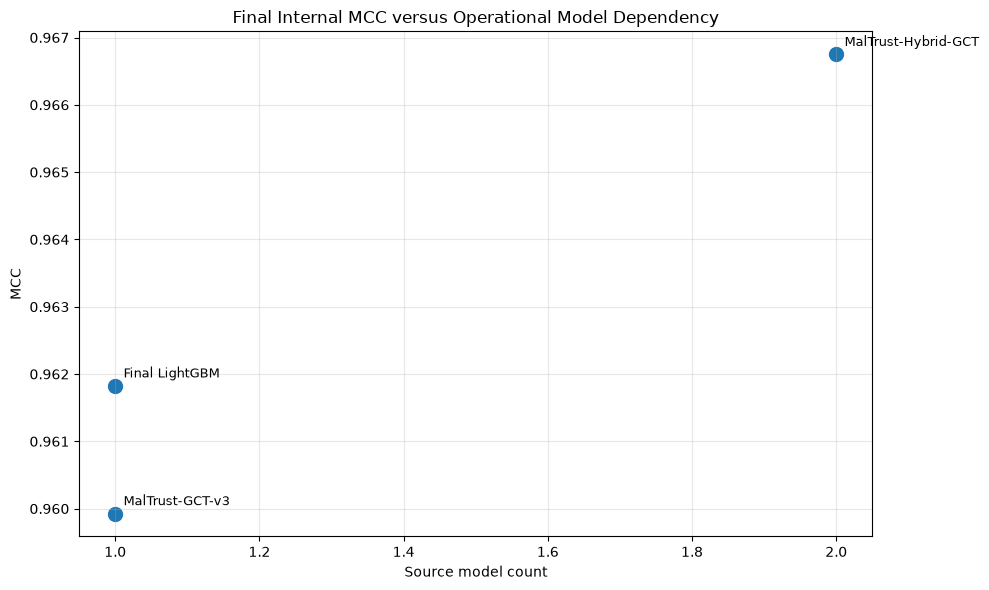

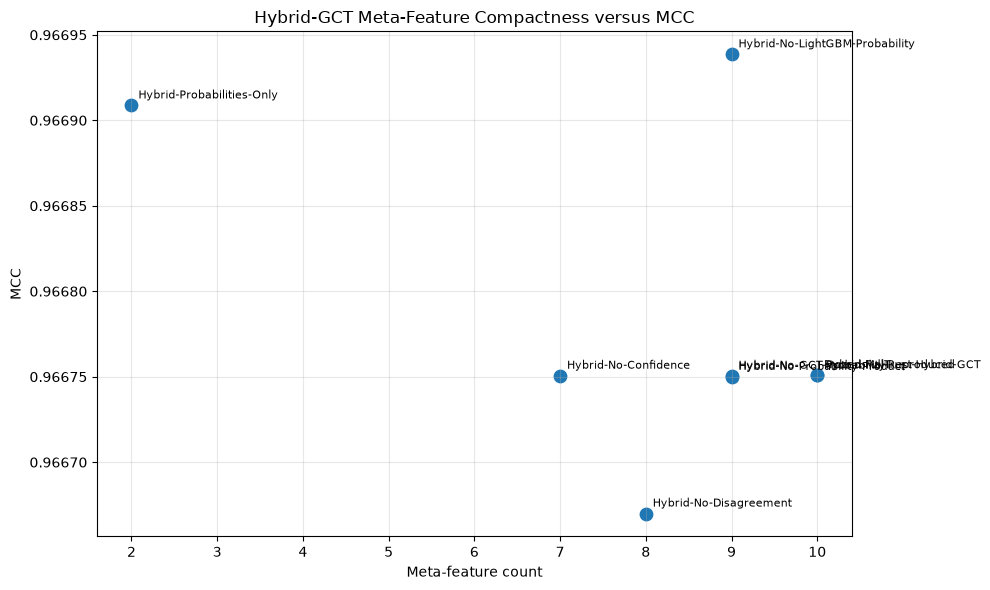

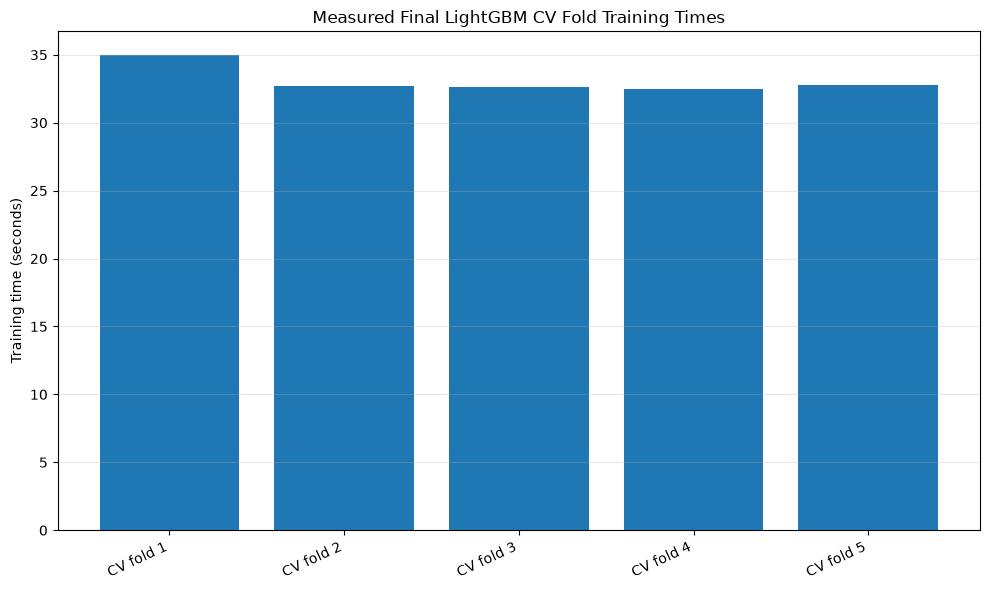

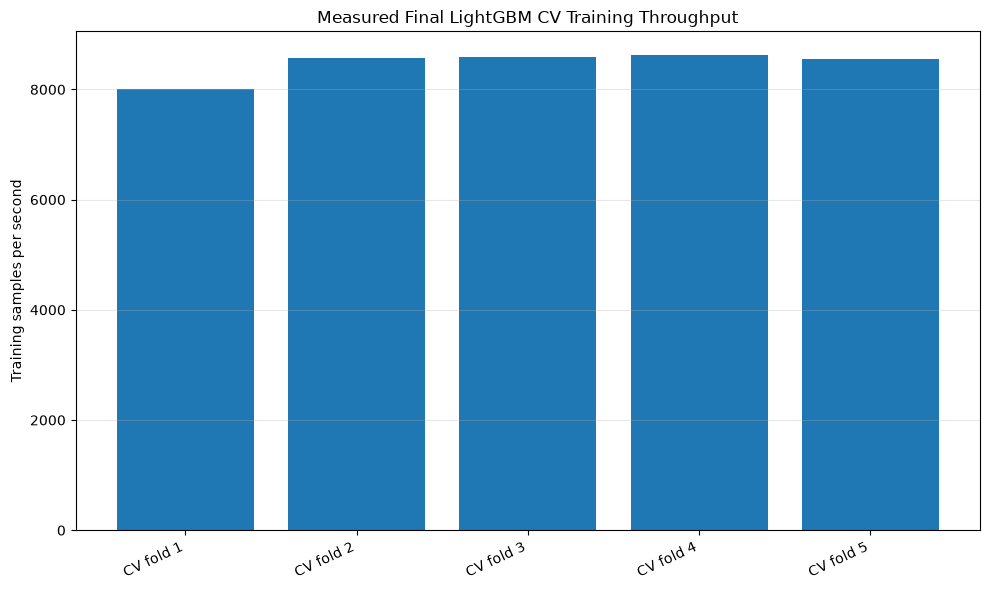


Post-Cell-24 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell24_hybrid_gct_efficiency_analysis\revised_strict_clean_699\Top_699_All\configs\cell24_experiment_config_snapshot.json
Post-Cell-24 experiment configuration snapshot SHA-256: cd05c806542be538e73c67b753da70a4b8b42232163145a5033a28507e9fe3d0

Cell 24 completed successfully.
Purpose: Hybrid-GCT computational efficiency and compactness analysis
Final Hybrid-GCT static feature count: 699
Final Hybrid-GCT meta-feature count: 10
Full Hybrid-GCT end-to-end runtime measured: False
Standalone LightGBM CV runtime rows: 6
Full efficiency table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell24_hybrid_gct_efficiency_analysis\revised_strict_clean_699\Top_699_All\tables\cell24_hybrid_gct_full_efficiency_analysis.csv
Manuscript efficiency table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell24_hybrid_gct_efficien

In [44]:
# ============================================================
# MalTrust-XAI | Cell 24
# Hybrid-GCT Computational Efficiency, Compactness, and Runtime-Claim Boundary Analysis
#
# Corrected purpose:
# - Use corrected Hybrid-GCT Cells 18-23, not old generic evidence objects.
# - Separate raw static-feature compactness from Hybrid-GCT meta-feature compactness.
# - Use real runtime only where measured, especially Cell 19 LightGBM CV fold times.
# - Do not claim Hybrid-GCT external efficiency or external superiority.
# - Produce manuscript-safe efficiency and compactness tables/figures.
# ============================================================

try:
    debug("Generating Hybrid-GCT computational-efficiency and compactness analysis...")
except Exception:
    pass

import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone


# ------------------------------------------------------------
# Safe helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is None:
        return
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def safe_sha256(path):
    try:
        if path is None or not os.path.exists(path) or os.path.isdir(path):
            return None
        return sha256_file(path)
    except Exception as e:
        print(f"SHA warning for {path}: {e}")
        return None


def first_existing_path(candidates):
    for path in candidates:
        if isinstance(path, str) and path.strip() and os.path.exists(path):
            return path
    return None


def read_first_existing_csv(candidates):
    path = first_existing_path(candidates)
    if path is None:
        return None, None
    return pd.read_csv(path), path


def latest_matching_file(pattern):
    matches = glob.glob(pattern, recursive=True)
    matches = [p for p in matches if os.path.isfile(p)]
    if not matches:
        return None
    matches = sorted(matches, key=lambda p: os.path.getmtime(p), reverse=True)
    return matches[0]


def numeric_or_nan(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def add_metric_aliases(df):
    df = df.copy()
    alias_map = {
        "Recall": "Recall_TPR",
        "F1_Score": "F1",
        "Specificity": "Specificity_TNR",
        "FPR": "False_Positive_Rate",
        "FNR": "False_Negative_Rate",
        "PR_AUC_Score": "PR_AUC",
        "Model_Name": "Model",
    }
    for old, new in alias_map.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]
    return df


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG", "sha256_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All"),
        )
    )

if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"
FULL_STATIC_FEATURE_COUNT = int(EXPERIMENT_CONFIG.get("cell15_final_feature_count", 699))
if FULL_STATIC_FEATURE_COUNT <= 0:
    FULL_STATIC_FEATURE_COUNT = 699

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        int(EXPERIMENT_CONFIG.get("active_train_files", 50)) * 10000,
    )
)
TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))
EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)
EXPECTED_TRAINVAL_ROWS = EXPECTED_TRAIN_ROWS + EXPECTED_VAL_ROWS

CELL24_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell24_hybrid_gct_efficiency_analysis",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL24_ARTIFACT_DIR, "tables")
FIGURE_DIR = os.path.join(CELL24_ARTIFACT_DIR, "figures")
REPORT_DIR = os.path.join(CELL24_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL24_ARTIFACT_DIR, "configs")

for directory in [CELL24_ARTIFACT_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(directory)

print("Cell 24 context:")
print("Purpose: Hybrid-GCT computational efficiency, compactness, and runtime-claim boundary analysis")
print("Framework:", FRAMEWORK_NAME)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Full static feature count:", FULL_STATIC_FEATURE_COUNT)
print("Artifact directory:", CELL24_ARTIFACT_DIR)


# ------------------------------------------------------------
# Resolve Cell 18 final internal model metrics
# ------------------------------------------------------------
final_metric_source = None

if "final_metric_comparison_plot_df" in globals():
    final_metric_df = final_metric_comparison_plot_df.copy()
    final_metric_source = "in_memory_final_metric_comparison_plot_df"
elif "final_internal_model_metrics_df" in globals():
    final_metric_df = final_internal_model_metrics_df.copy()
    final_metric_source = "in_memory_final_internal_model_metrics_df"
elif "final_manuscript_ready_results_df" in globals():
    final_metric_df = final_manuscript_ready_results_df.copy()
    final_metric_source = "in_memory_final_manuscript_ready_results_df"
else:
    candidates = [
        EXPERIMENT_CONFIG.get("cell18_metric_table_path", None),
        EXPERIMENT_CONFIG.get("cell15_manuscript_ready_results_path", None),
        EXPERIMENT_CONFIG.get("cell15_final_internal_results_path", None),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell18_final_internal_model_metric_table.csv")),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "manuscript_ready_internal_results_top_699_all.csv")),
    ]
    final_metric_df, final_metric_source = read_first_existing_csv(candidates)

if final_metric_df is None or final_metric_df.empty:
    raise FileNotFoundError(
        "Could not resolve final internal model metric table from Cell 18/15. "
        "Run corrected Cell 18 before Cell 24."
    )

final_metric_df = add_metric_aliases(final_metric_df)
if "Model" not in final_metric_df.columns:
    raise ValueError("Final metric table must contain a Model column.")

primary_models = ["MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"]
final_metric_df["Model"] = final_metric_df["Model"].astype(str)
final_metric_df = final_metric_df[final_metric_df["Model"].isin(primary_models)].copy()

if final_metric_df.empty:
    raise ValueError("Final metric table did not contain the expected final models.")

print("Final metric source:", final_metric_source)
print("Final metric rows:", len(final_metric_df))


# ------------------------------------------------------------
# Resolve Cell 20 Hybrid-GCT ablation metrics/design
# ------------------------------------------------------------
ablation_metrics_source = None
ablation_design_source = None

if "hybrid_gct_ablation_metrics_df" in globals():
    ablation_metrics_df = hybrid_gct_ablation_metrics_df.copy()
    ablation_metrics_source = "in_memory_hybrid_gct_ablation_metrics_df"
else:
    candidates = [
        EXPERIMENT_CONFIG.get("cell20_hybrid_gct_ablation_metrics_path", None),
        EXPERIMENT_CONFIG.get("cell20_ablation_metrics_path", None),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell20_hybrid_gct_ablation_metrics.csv")),
    ]
    ablation_metrics_df, ablation_metrics_source = read_first_existing_csv(candidates)

if "hybrid_gct_ablation_design_df" in globals():
    ablation_design_df = hybrid_gct_ablation_design_df.copy()
    ablation_design_source = "in_memory_hybrid_gct_ablation_design_df"
else:
    candidates = [
        EXPERIMENT_CONFIG.get("cell20_hybrid_gct_ablation_design_path", None),
        EXPERIMENT_CONFIG.get("cell20_ablation_design_path", None),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell20_hybrid_gct_ablation_design.csv")),
    ]
    ablation_design_df, ablation_design_source = read_first_existing_csv(candidates)

if ablation_metrics_df is None:
    ablation_metrics_df = pd.DataFrame()
    ablation_metrics_source = "not_available"
else:
    ablation_metrics_df = add_metric_aliases(ablation_metrics_df)

if ablation_design_df is None:
    ablation_design_df = pd.DataFrame()
    ablation_design_source = "not_available"

print("Ablation metrics source:", ablation_metrics_source)
print("Ablation design source:", ablation_design_source)


# ------------------------------------------------------------
# Resolve Cell 19 LightGBM CV runtime audit
# ------------------------------------------------------------
cv_fold_source = None
cv_summary_source = None

if "final_subset_cv_fold_results_df" in globals():
    cv_fold_df = final_subset_cv_fold_results_df.copy()
    cv_fold_source = "in_memory_final_subset_cv_fold_results_df"
else:
    candidates = [
        EXPERIMENT_CONFIG.get("cell19_cv_fold_results_path", None),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell19_cv_fold_results_*.csv")),
    ]
    cv_fold_df, cv_fold_source = read_first_existing_csv(candidates)

if "final_subset_cv_summary_df" in globals():
    cv_summary_df = final_subset_cv_summary_df.copy()
    cv_summary_source = "in_memory_final_subset_cv_summary_df"
else:
    candidates = [
        EXPERIMENT_CONFIG.get("cell19_cv_summary_path", None),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell19_cv_summary_*.csv")),
    ]
    cv_summary_df, cv_summary_source = read_first_existing_csv(candidates)

if cv_fold_df is None:
    cv_fold_df = pd.DataFrame()
    cv_fold_source = "not_available"
if cv_summary_df is None:
    cv_summary_df = pd.DataFrame()
    cv_summary_source = "not_available"

print("CV fold source:", cv_fold_source)
print("CV summary source:", cv_summary_source)


# ------------------------------------------------------------
# Resolve Cell 22 integrity summary if available
# ------------------------------------------------------------
integrity_summary = {
    "Artifact_Count_Hashed": np.nan,
    "Hash_Chain_Validation_Passed": np.nan,
    "Hash_Chain_Root": None,
}

if "final_framework_integrity_report" in globals() and isinstance(final_framework_integrity_report, dict):
    integrity_summary["Artifact_Count_Hashed"] = final_framework_integrity_report.get("artifact_count_hashed", np.nan)
    integrity_summary["Hash_Chain_Validation_Passed"] = final_framework_integrity_report.get("chain_validation_passed", np.nan)
    integrity_summary["Hash_Chain_Root"] = final_framework_integrity_report.get("hash_chain_root", None)
else:
    integrity_report_path = first_existing_path([
        EXPERIMENT_CONFIG.get("cell22_integrity_report_path", None),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell22_hybrid_gct_integrity_manifest_report.json")),
        latest_matching_file(os.path.join(FRAMEWORK_ARTIFACT_DIR, "**", "cell22_integrity_manifest_report.json")),
    ])
    if integrity_report_path:
        try:
            with open(integrity_report_path, "r", encoding="utf-8") as f:
                report = json.load(f)
            integrity_summary["Artifact_Count_Hashed"] = report.get("artifact_count_hashed", report.get("artifacts_hashed", np.nan))
            integrity_summary["Hash_Chain_Validation_Passed"] = report.get("chain_validation_passed", np.nan)
            integrity_summary["Hash_Chain_Root"] = report.get("hash_chain_root", None)
        except Exception as e:
            print("Integrity report read warning:", e)


# ------------------------------------------------------------
# Build final-model efficiency table
# ------------------------------------------------------------
model_dependency_map = {
    "MalTrust-Hybrid-GCT": {
        "Static_Feature_Count": FULL_STATIC_FEATURE_COUNT,
        "Meta_Feature_Count": 10,
        "Source_Model_Count": 2,
        "Requires_LightGBM_Source": True,
        "Requires_GCT_Source": True,
        "Operational_Dependency": "Final LightGBM probability + GCT-v3 probability + validation-trained 10-feature meta-calibrator",
        "Runtime_Claim_Level": "No direct end-to-end runtime measured in this cell; report structural compactness only",
    },
    "Final LightGBM": {
        "Static_Feature_Count": FULL_STATIC_FEATURE_COUNT,
        "Meta_Feature_Count": 0,
        "Source_Model_Count": 1,
        "Requires_LightGBM_Source": True,
        "Requires_GCT_Source": False,
        "Operational_Dependency": "Final standalone LightGBM over 699 strict-clean static PE features",
        "Runtime_Claim_Level": "Training runtime supported only by Cell 19 CV audit, not final end-to-end package runtime",
    },
    "MalTrust-GCT-v3": {
        "Static_Feature_Count": FULL_STATIC_FEATURE_COUNT,
        "Meta_Feature_Count": 0,
        "Source_Model_Count": 1,
        "Requires_LightGBM_Source": False,
        "Requires_GCT_Source": True,
        "Operational_Dependency": "Group-aware neural auxiliary detector over strict-clean static PE feature groups",
        "Runtime_Claim_Level": "No direct end-to-end runtime measured in this cell; report structural compactness only",
    },
}

final_rows = []
metric_cols = [
    "Accuracy", "Balanced_Accuracy", "Precision", "Recall_TPR", "Specificity_TNR",
    "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE",
    "False_Positive_Rate", "False_Negative_Rate", "TN", "FP", "FN", "TP",
]

for _, row in final_metric_df.iterrows():
    model = str(row["Model"])
    dep = model_dependency_map.get(model, {})
    payload = {
        "Analysis_Table": "final_internal_model_efficiency",
        "Model": model,
        "Variant": model,
        "Evidence_Level": "Held-out SHA-disjoint internal test",
        "Testing_Samples": int(row.get("Samples", EXPECTED_TEST_ROWS)) if pd.notna(row.get("Samples", EXPECTED_TEST_ROWS)) else EXPECTED_TEST_ROWS,
        "Static_Feature_Count": dep.get("Static_Feature_Count", FULL_STATIC_FEATURE_COUNT),
        "Meta_Feature_Count": dep.get("Meta_Feature_Count", 0),
        "Source_Model_Count": dep.get("Source_Model_Count", np.nan),
        "Requires_LightGBM_Source": dep.get("Requires_LightGBM_Source", False),
        "Requires_GCT_Source": dep.get("Requires_GCT_Source", False),
        "Operational_Dependency": dep.get("Operational_Dependency", "not specified"),
        "Training_Time_Seconds": numeric_or_nan(row.get("Training_Time_Seconds", np.nan)),
        "Inference_Time_Seconds": numeric_or_nan(row.get("Inference_Time_Seconds", np.nan)),
        "Runtime_Claim_Level": dep.get("Runtime_Claim_Level", "No direct runtime measured"),
        "May_Claim_Runtime_Efficiency": False,
        "May_Claim_Static_Feature_Compactness": True,
        "May_Claim_Meta_Feature_Compactness": model == "MalTrust-Hybrid-GCT",
        "Source_Object": final_metric_source,
    }
    for metric in metric_cols:
        payload[metric] = numeric_or_nan(row.get(metric, np.nan))
    final_rows.append(payload)

final_efficiency_df = pd.DataFrame(final_rows)

# Derived performance-per-count values.
for df in [final_efficiency_df]:
    df["MCC_Per_Static_Feature"] = df["MCC"] / df["Static_Feature_Count"]
    df["ROC_AUC_Per_Static_Feature"] = df["ROC_AUC"] / df["Static_Feature_Count"]
    df["F1_Per_Static_Feature"] = df["F1"] / df["Static_Feature_Count"]
    df["MCC_Per_Meta_Feature"] = np.where(df["Meta_Feature_Count"] > 0, df["MCC"] / df["Meta_Feature_Count"], np.nan)


# ------------------------------------------------------------
# Build meta-calibrator ablation compactness table from Cell 20
# ------------------------------------------------------------
meta_rows = []
if not ablation_metrics_df.empty:
    for _, row in ablation_metrics_df.iterrows():
        variant = str(row.get("Variant", row.get("Model", "unknown_variant")))
        variant_type = str(row.get("Variant_Type", "unknown"))
        training_mode = str(row.get("Training_Mode", "unknown"))
        meta_count = int(row.get("Feature_Count", 0)) if pd.notna(row.get("Feature_Count", 0)) else 0
        is_hybrid_like = variant.startswith("Hybrid-") or "Hybrid-GCT" in variant
        payload = {
            "Analysis_Table": "hybrid_meta_ablation_compactness",
            "Model": variant,
            "Variant": variant,
            "Variant_Type": variant_type,
            "Training_Mode": training_mode,
            "Evidence_Level": "Held-out internal test ablation",
            "Testing_Samples": int(row.get("Samples", EXPECTED_TEST_ROWS)) if pd.notna(row.get("Samples", EXPECTED_TEST_ROWS)) else EXPECTED_TEST_ROWS,
            "Static_Feature_Count": FULL_STATIC_FEATURE_COUNT if is_hybrid_like or variant in ["Final LightGBM", "MalTrust-GCT-v3"] else np.nan,
            "Meta_Feature_Count": meta_count,
            "Source_Model_Count": 2 if is_hybrid_like else 1,
            "Requires_LightGBM_Source": bool(is_hybrid_like or variant == "Final LightGBM"),
            "Requires_GCT_Source": bool(is_hybrid_like or variant == "MalTrust-GCT-v3"),
            "Operational_Dependency": "Exploratory meta-calibrator ablation; meta-feature compactness only",
            "Training_Time_Seconds": numeric_or_nan(row.get("Training_Time_Seconds", np.nan)),
            "Inference_Time_Seconds": numeric_or_nan(row.get("Inference_Time_Seconds", np.nan)),
            "Runtime_Claim_Level": "No end-to-end runtime claim; ablation uses frozen source-model probabilities and retrains only meta-calibrator when applicable",
            "May_Claim_Runtime_Efficiency": False,
            "May_Claim_Static_Feature_Compactness": False,
            "May_Claim_Meta_Feature_Compactness": bool(is_hybrid_like and meta_count > 0),
            "Source_Object": ablation_metrics_source,
        }
        for metric in metric_cols:
            payload[metric] = numeric_or_nan(row.get(metric, np.nan))
        payload["Selected_Threshold"] = numeric_or_nan(row.get("Selected_Threshold", np.nan))
        payload["Validation_MCC_For_Threshold"] = numeric_or_nan(row.get("Validation_MCC_For_Threshold", np.nan))
        meta_rows.append(payload)

meta_compactness_df = pd.DataFrame(meta_rows)
if not meta_compactness_df.empty:
    meta_compactness_df["MCC_Per_Static_Feature"] = meta_compactness_df["MCC"] / meta_compactness_df["Static_Feature_Count"]
    meta_compactness_df["ROC_AUC_Per_Static_Feature"] = meta_compactness_df["ROC_AUC"] / meta_compactness_df["Static_Feature_Count"]
    meta_compactness_df["F1_Per_Static_Feature"] = meta_compactness_df["F1"] / meta_compactness_df["Static_Feature_Count"]
    meta_compactness_df["MCC_Per_Meta_Feature"] = np.where(
        meta_compactness_df["Meta_Feature_Count"] > 0,
        meta_compactness_df["MCC"] / meta_compactness_df["Meta_Feature_Count"],
        np.nan,
    )


# ------------------------------------------------------------
# Build Cell 19 real runtime table for standalone Final LightGBM CV
# ------------------------------------------------------------
cv_runtime_rows = []
if not cv_fold_df.empty and "Training_Time_Seconds" in cv_fold_df.columns:
    cv_fold_work = cv_fold_df.copy()
    cv_fold_work["Training_Time_Seconds"] = pd.to_numeric(cv_fold_work["Training_Time_Seconds"], errors="coerce")
    cv_fold_work = add_metric_aliases(cv_fold_work)

    # Fold-level runtime rows.
    for _, row in cv_fold_work.iterrows():
        train_rows = int(row.get("Train_Rows", 0)) if pd.notna(row.get("Train_Rows", np.nan)) else np.nan
        train_seconds = numeric_or_nan(row.get("Training_Time_Seconds", np.nan))
        payload = {
            "Analysis_Table": "standalone_lightgbm_cv_runtime_fold",
            "Model": "Final LightGBM",
            "Variant": f"CV fold {int(row.get('Fold_ID', 0))}" if pd.notna(row.get("Fold_ID", np.nan)) else "CV fold",
            "Evidence_Level": "Training-split cross-validation runtime audit",
            "Training_Samples": train_rows,
            "Validation_Samples": int(row.get("Validation_Rows", 0)) if pd.notna(row.get("Validation_Rows", np.nan)) else np.nan,
            "Static_Feature_Count": int(row.get("Feature_Count", FULL_STATIC_FEATURE_COUNT)) if pd.notna(row.get("Feature_Count", np.nan)) else FULL_STATIC_FEATURE_COUNT,
            "Meta_Feature_Count": 0,
            "Source_Model_Count": 1,
            "Requires_LightGBM_Source": True,
            "Requires_GCT_Source": False,
            "Training_Time_Seconds": train_seconds,
            "Training_Samples_Per_Second": train_rows / train_seconds if pd.notna(train_seconds) and train_seconds > 0 else np.nan,
            "Operational_Dependency": "Measured standalone Final LightGBM fold training runtime on training split only",
            "Runtime_Claim_Level": "Real measured training runtime for standalone Final LightGBM CV folds only",
            "May_Claim_Runtime_Efficiency": True,
            "May_Claim_Static_Feature_Compactness": True,
            "May_Claim_Meta_Feature_Compactness": False,
            "Source_Object": cv_fold_source,
        }
        for metric in metric_cols:
            payload[metric] = numeric_or_nan(row.get(metric, np.nan))
        cv_runtime_rows.append(payload)

    # Mean runtime row.
    mean_train_seconds = float(cv_fold_work["Training_Time_Seconds"].mean())
    std_train_seconds = float(cv_fold_work["Training_Time_Seconds"].std(ddof=1)) if len(cv_fold_work) > 1 else 0.0
    mean_train_rows = int(round(float(pd.to_numeric(cv_fold_work.get("Train_Rows", pd.Series([EXPECTED_TRAIN_ROWS])), errors="coerce").mean())))
    cv_metric_means = {}
    for metric in metric_cols:
        if metric in cv_fold_work.columns:
            cv_metric_means[metric] = float(pd.to_numeric(cv_fold_work[metric], errors="coerce").mean())
        else:
            cv_metric_means[metric] = np.nan

    payload = {
        "Analysis_Table": "standalone_lightgbm_cv_runtime_mean",
        "Model": "Final LightGBM",
        "Variant": "Cell 19 CV mean",
        "Evidence_Level": "Training-split cross-validation runtime audit",
        "Training_Samples": mean_train_rows,
        "Validation_Samples": int(round(float(pd.to_numeric(cv_fold_work.get("Validation_Rows", pd.Series([EXPECTED_VAL_ROWS])), errors="coerce").mean()))),
        "Static_Feature_Count": FULL_STATIC_FEATURE_COUNT,
        "Meta_Feature_Count": 0,
        "Source_Model_Count": 1,
        "Requires_LightGBM_Source": True,
        "Requires_GCT_Source": False,
        "Training_Time_Seconds": mean_train_seconds,
        "Training_Time_Std_Seconds": std_train_seconds,
        "Training_Samples_Per_Second": mean_train_rows / mean_train_seconds if mean_train_seconds > 0 else np.nan,
        "Operational_Dependency": "Mean measured standalone Final LightGBM fold training runtime",
        "Runtime_Claim_Level": "Real measured training runtime for standalone Final LightGBM CV only; not Hybrid-GCT end-to-end runtime",
        "May_Claim_Runtime_Efficiency": True,
        "May_Claim_Static_Feature_Compactness": True,
        "May_Claim_Meta_Feature_Compactness": False,
        "Source_Object": cv_fold_source,
    }
    payload.update(cv_metric_means)
    cv_runtime_rows.append(payload)

cv_runtime_df = pd.DataFrame(cv_runtime_rows)
if not cv_runtime_df.empty:
    cv_runtime_df["MCC_Per_Static_Feature"] = cv_runtime_df["MCC"] / cv_runtime_df["Static_Feature_Count"]
    cv_runtime_df["ROC_AUC_Per_Static_Feature"] = cv_runtime_df["ROC_AUC"] / cv_runtime_df["Static_Feature_Count"]
    cv_runtime_df["F1_Per_Static_Feature"] = cv_runtime_df["F1"] / cv_runtime_df["Static_Feature_Count"]
    cv_runtime_df["MCC_Per_Training_Second"] = cv_runtime_df["MCC"] / cv_runtime_df["Training_Time_Seconds"]
    cv_runtime_df["Accuracy_Per_Training_Second"] = cv_runtime_df["Accuracy"] / cv_runtime_df["Training_Time_Seconds"]


# ------------------------------------------------------------
# Operational dependency / claim-boundary table
# ------------------------------------------------------------
claim_rows = [
    {
        "Claim_Type": "Allowed structural compactness claim",
        "Claim": "The final Hybrid-GCT meta-calibrator uses 10 validation-trained meta-features on top of the 699 strict-clean static PE feature space.",
        "Allowed": True,
        "Evidence_Source": "Cells 11F, 15, 18, 20, 21",
    },
    {
        "Claim_Type": "Allowed standalone LightGBM runtime claim",
        "Claim": "Standalone Final LightGBM training runtime was measured in the Cell 19 training-split CV audit.",
        "Allowed": bool(not cv_runtime_df.empty),
        "Evidence_Source": "Cell 19",
    },
    {
        "Claim_Type": "Not allowed Hybrid-GCT end-to-end runtime claim",
        "Claim": "Do not claim final Hybrid-GCT end-to-end training/inference runtime unless separately measured for the full LightGBM + GCT + meta-calibrator pipeline.",
        "Allowed": False,
        "Evidence_Source": "No full end-to-end Hybrid-GCT runtime cell yet",
    },
    {
        "Claim_Type": "Not allowed external efficiency claim",
        "Claim": "Do not claim external Hybrid-GCT runtime or external superiority until External Stage 3 and dedicated external runtime measurements are completed.",
        "Allowed": False,
        "Evidence_Source": "External Stage 3 pending",
    },
]
claim_boundary_df = pd.DataFrame(claim_rows)

operational_dependency_rows = []
for model in primary_models:
    dep = model_dependency_map.get(model, {})
    operational_dependency_rows.append({
        "Model": model,
        "Static_Feature_Count": dep.get("Static_Feature_Count", FULL_STATIC_FEATURE_COUNT),
        "Meta_Feature_Count": dep.get("Meta_Feature_Count", 0),
        "Source_Model_Count": dep.get("Source_Model_Count", np.nan),
        "Requires_LightGBM_Source": dep.get("Requires_LightGBM_Source", False),
        "Requires_GCT_Source": dep.get("Requires_GCT_Source", False),
        "Operational_Dependency": dep.get("Operational_Dependency", "not specified"),
        "Runtime_Claim_Level": dep.get("Runtime_Claim_Level", "not specified"),
    })
operational_dependency_df = pd.DataFrame(operational_dependency_rows)


# ------------------------------------------------------------
# Combine full efficiency evidence
# ------------------------------------------------------------
combined_frames = [final_efficiency_df]
if not meta_compactness_df.empty:
    combined_frames.append(meta_compactness_df)
if not cv_runtime_df.empty:
    combined_frames.append(cv_runtime_df)

full_efficiency_df = pd.concat(combined_frames, ignore_index=True, sort=False)

# Clean numerical columns.
for col in [
    "Static_Feature_Count", "Meta_Feature_Count", "Source_Model_Count", "Testing_Samples",
    "Training_Samples", "Validation_Samples", "Training_Time_Seconds",
    "Inference_Time_Seconds", "Training_Samples_Per_Second",
    "MCC", "Accuracy", "F1", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE",
    "False_Positive_Rate", "False_Negative_Rate", "MCC_Per_Static_Feature",
    "MCC_Per_Meta_Feature", "MCC_Per_Training_Second",
]:
    if col in full_efficiency_df.columns:
        full_efficiency_df[col] = pd.to_numeric(full_efficiency_df[col], errors="coerce")

full_efficiency_df["Static_Feature_Reduction_Percent_vs_699"] = 100.0 * (
    1.0 - full_efficiency_df["Static_Feature_Count"] / FULL_STATIC_FEATURE_COUNT
)
full_efficiency_df["Static_Feature_Reduction_Percent_vs_699"] = full_efficiency_df["Static_Feature_Reduction_Percent_vs_699"].clip(lower=0.0)

# Mark final retained model.
full_efficiency_df["Final_Model_Retained"] = full_efficiency_df["Variant"].astype(str).isin([
    "MalTrust-Hybrid-GCT", "Frozen MalTrust-Hybrid-GCT"
])
full_efficiency_df["External_Hybrid_GCT_Validated"] = False

# Sort with final internal models first, then ablations, then CV runtime.
priority_map = {
    "final_internal_model_efficiency": 1,
    "hybrid_meta_ablation_compactness": 2,
    "standalone_lightgbm_cv_runtime_mean": 3,
    "standalone_lightgbm_cv_runtime_fold": 4,
}
full_efficiency_df["Analysis_Priority"] = full_efficiency_df["Analysis_Table"].map(priority_map).fillna(99).astype(int)
full_efficiency_df["Rank_Within_Analysis_Table"] = full_efficiency_df.groupby("Analysis_Table")["MCC"].rank(ascending=False, method="dense")
full_efficiency_df = full_efficiency_df.sort_values(
    ["Analysis_Priority", "Rank_Within_Analysis_Table", "Variant"],
    ascending=[True, True, True]
).reset_index(drop=True)
full_efficiency_df.insert(0, "Efficiency_Row_ID", np.arange(1, len(full_efficiency_df) + 1))

# Manuscript table: concise, safe columns only.
manuscript_cols = [
    "Efficiency_Row_ID", "Analysis_Table", "Evidence_Level", "Model", "Variant",
    "Static_Feature_Count", "Meta_Feature_Count", "Source_Model_Count",
    "Requires_LightGBM_Source", "Requires_GCT_Source",
    "Testing_Samples", "Training_Samples", "Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC",
    "Brier_Score", "ECE", "False_Positive_Rate", "False_Negative_Rate",
    "Training_Time_Seconds", "Training_Samples_Per_Second",
    "MCC_Per_Static_Feature", "MCC_Per_Meta_Feature", "MCC_Per_Training_Second",
    "May_Claim_Runtime_Efficiency", "May_Claim_Static_Feature_Compactness",
    "May_Claim_Meta_Feature_Compactness", "Runtime_Claim_Level", "Final_Model_Retained",
    "External_Hybrid_GCT_Validated",
]
manuscript_cols = [c for c in manuscript_cols if c in full_efficiency_df.columns]
manuscript_efficiency_df = full_efficiency_df[manuscript_cols].copy()

print("\nHybrid-GCT final model efficiency/compactness table:")
display(final_efficiency_df)

print("\nHybrid-GCT meta-feature compactness table:")
display(meta_compactness_df if not meta_compactness_df.empty else pd.DataFrame({"status": ["not_available"]}))

print("\nStandalone Final LightGBM CV runtime table:")
display(cv_runtime_df if not cv_runtime_df.empty else pd.DataFrame({"status": ["not_available"]}))

print("\nOperational dependency table:")
display(operational_dependency_df)

print("\nRuntime and efficiency claim-boundary table:")
display(claim_boundary_df)

print("\nManuscript-safe computational efficiency table:")
display(manuscript_efficiency_df)


# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------
full_efficiency_path = os.path.join(TABLE_DIR, "cell24_hybrid_gct_full_efficiency_analysis.csv")
manuscript_efficiency_path = os.path.join(TABLE_DIR, "cell24_hybrid_gct_manuscript_efficiency_table.csv")
final_model_efficiency_path = os.path.join(TABLE_DIR, "cell24_hybrid_gct_final_model_efficiency_table.csv")
meta_compactness_path = os.path.join(TABLE_DIR, "cell24_hybrid_gct_meta_feature_compactness_table.csv")
cv_runtime_path = os.path.join(TABLE_DIR, "cell24_final_lightgbm_cv_runtime_table.csv")
operational_dependency_path = os.path.join(TABLE_DIR, "cell24_hybrid_gct_operational_dependency_table.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "cell24_efficiency_claim_boundary_table.csv")

safe_save_csv(full_efficiency_df, full_efficiency_path, index=False)
safe_save_csv(manuscript_efficiency_df, manuscript_efficiency_path, index=False)
safe_save_csv(final_efficiency_df, final_model_efficiency_path, index=False)
safe_save_csv(meta_compactness_df, meta_compactness_path, index=False)
safe_save_csv(cv_runtime_df, cv_runtime_path, index=False)
safe_save_csv(operational_dependency_df, operational_dependency_path, index=False)
safe_save_csv(claim_boundary_df, claim_boundary_path, index=False)


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------
def save_bar_metric(df, metric, title, ylabel, output_path, sort_desc=True):
    plot_df = df[df[metric].notna()].copy()
    if plot_df.empty:
        return None
    plot_df = plot_df.sort_values(metric, ascending=not sort_desc)
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["Variant"].astype(str), plot_df[metric].astype(float))
    plt.xticks(rotation=25, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    ensure_parent_dir(output_path)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return output_path

# Figure 1: final internal model MCC vs operational source-model count.
final_mcc_source_figure_path = os.path.join(FIGURE_DIR, "cell24_final_model_mcc_by_operational_dependency.png")
plt.figure(figsize=(10, 6))
plt.scatter(
    final_efficiency_df["Source_Model_Count"].astype(float),
    final_efficiency_df["MCC"].astype(float),
    s=100,
)
for _, row in final_efficiency_df.iterrows():
    plt.annotate(
        str(row["Model"]),
        (float(row["Source_Model_Count"]), float(row["MCC"])),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )
plt.xlabel("Source model count")
plt.ylabel("MCC")
plt.title("Final Internal MCC versus Operational Model Dependency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(final_mcc_source_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Figure 2: meta-feature count vs MCC among Hybrid ablations.
meta_feature_mcc_figure_path = None
if not meta_compactness_df.empty:
    meta_plot_df = meta_compactness_df[
        meta_compactness_df["Meta_Feature_Count"].notna()
        & meta_compactness_df["MCC"].notna()
        & meta_compactness_df["May_Claim_Meta_Feature_Compactness"].astype(bool)
    ].copy()
    if not meta_plot_df.empty:
        meta_feature_mcc_figure_path = os.path.join(FIGURE_DIR, "cell24_meta_feature_count_vs_mcc.png")
        plt.figure(figsize=(10, 6))
        plt.scatter(meta_plot_df["Meta_Feature_Count"].astype(float), meta_plot_df["MCC"].astype(float), s=80)
        for _, row in meta_plot_df.iterrows():
            plt.annotate(
                str(row["Variant"])[:35],
                (float(row["Meta_Feature_Count"]), float(row["MCC"])),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
            )
        plt.xlabel("Meta-feature count")
        plt.ylabel("MCC")
        plt.title("Hybrid-GCT Meta-Feature Compactness versus MCC")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(meta_feature_mcc_figure_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

# Figure 3: real Cell 19 LightGBM CV fold training times.
cv_training_time_figure_path = None
if not cv_runtime_df.empty:
    fold_plot_df = cv_runtime_df[cv_runtime_df["Analysis_Table"].eq("standalone_lightgbm_cv_runtime_fold")].copy()
    if not fold_plot_df.empty:
        cv_training_time_figure_path = os.path.join(FIGURE_DIR, "cell24_final_lightgbm_cv_fold_training_times.png")
        plt.figure(figsize=(10, 6))
        plt.bar(fold_plot_df["Variant"].astype(str), fold_plot_df["Training_Time_Seconds"].astype(float))
        plt.xticks(rotation=25, ha="right")
        plt.ylabel("Training time (seconds)")
        plt.title("Measured Final LightGBM CV Fold Training Times")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(cv_training_time_figure_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

# Figure 4: LightGBM training throughput if available.
cv_throughput_figure_path = None
if not cv_runtime_df.empty and "Training_Samples_Per_Second" in cv_runtime_df.columns:
    fold_plot_df = cv_runtime_df[
        cv_runtime_df["Analysis_Table"].eq("standalone_lightgbm_cv_runtime_fold")
        & cv_runtime_df["Training_Samples_Per_Second"].notna()
    ].copy()
    if not fold_plot_df.empty:
        cv_throughput_figure_path = os.path.join(FIGURE_DIR, "cell24_final_lightgbm_cv_training_throughput.png")
        plt.figure(figsize=(10, 6))
        plt.bar(fold_plot_df["Variant"].astype(str), fold_plot_df["Training_Samples_Per_Second"].astype(float))
        plt.xticks(rotation=25, ha="right")
        plt.ylabel("Training samples per second")
        plt.title("Measured Final LightGBM CV Training Throughput")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(cv_throughput_figure_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


# ------------------------------------------------------------
# JSON report and artifacts
# ------------------------------------------------------------
cell24_report_path = os.path.join(REPORT_DIR, "cell24_hybrid_gct_efficiency_analysis_report.json")

cell24_report = {
    "cell": "Cell 24",
    "cell_name": "Hybrid-GCT Computational Efficiency and Compactness Analysis",
    "framework_name": FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "full_static_feature_count": int(FULL_STATIC_FEATURE_COUNT),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "source_final_metric_table": final_metric_source,
    "source_ablation_metrics": ablation_metrics_source,
    "source_ablation_design": ablation_design_source,
    "source_cv_fold_runtime": cv_fold_source,
    "source_cv_summary": cv_summary_source,
    "analysis_policy": (
        "Runtime claims are separated from feature-compactness claims. "
        "Only standalone Final LightGBM CV fold training time is treated as directly measured runtime evidence. "
        "Hybrid-GCT final end-to-end runtime is not claimed unless a dedicated full-pipeline runtime cell is added."
    ),
    "final_hybrid_static_feature_count": int(FULL_STATIC_FEATURE_COUNT),
    "final_hybrid_meta_feature_count": 10,
    "final_hybrid_source_model_count": 2,
    "artifact_integrity_summary": integrity_summary,
    "external_hybrid_gct_validated": False,
    "tables": {
        "full_efficiency_analysis": full_efficiency_path,
        "manuscript_efficiency_table": manuscript_efficiency_path,
        "final_model_efficiency_table": final_model_efficiency_path,
        "meta_feature_compactness_table": meta_compactness_path,
        "final_lightgbm_cv_runtime_table": cv_runtime_path,
        "operational_dependency_table": operational_dependency_path,
        "claim_boundary_table": claim_boundary_path,
    },
    "figures": {
        "final_mcc_by_operational_dependency": final_mcc_source_figure_path,
        "meta_feature_count_vs_mcc": meta_feature_mcc_figure_path,
        "final_lightgbm_cv_fold_training_times": cv_training_time_figure_path,
        "final_lightgbm_cv_training_throughput": cv_throughput_figure_path,
    },
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}

safe_save_json(cell24_report, cell24_report_path)

cell24_artifacts = {
    "full_efficiency_analysis": full_efficiency_path,
    "manuscript_efficiency_table": manuscript_efficiency_path,
    "final_model_efficiency_table": final_model_efficiency_path,
    "meta_feature_compactness_table": meta_compactness_path,
    "final_lightgbm_cv_runtime_table": cv_runtime_path,
    "operational_dependency_table": operational_dependency_path,
    "efficiency_claim_boundary_table": claim_boundary_path,
    "efficiency_analysis_report": cell24_report_path,
    "final_mcc_by_operational_dependency_figure": final_mcc_source_figure_path,
}
if meta_feature_mcc_figure_path is not None:
    cell24_artifacts["meta_feature_count_vs_mcc_figure"] = meta_feature_mcc_figure_path
if cv_training_time_figure_path is not None:
    cell24_artifacts["final_lightgbm_cv_training_time_figure"] = cv_training_time_figure_path
if cv_throughput_figure_path is not None:
    cell24_artifacts["final_lightgbm_cv_training_throughput_figure"] = cv_throughput_figure_path

cell24_artifact_rows = []
for artifact_name, artifact_path in cell24_artifacts.items():
    if artifact_path is not None and os.path.exists(artifact_path):
        cell24_artifact_rows.append({
            "artifact_name": artifact_name,
            "artifact_path": artifact_path,
            "sha256": safe_sha256(artifact_path),
            "registered_at": now_str(),
        })

cell24_artifact_hashes_path = os.path.join(CELL24_ARTIFACT_DIR, "cell24_artifact_hashes.csv")
safe_save_csv(pd.DataFrame(cell24_artifact_rows), cell24_artifact_hashes_path, index=False)

cell24_artifact_rows.append({
    "artifact_name": "cell24_artifact_hashes",
    "artifact_path": cell24_artifact_hashes_path,
    "sha256": safe_sha256(cell24_artifact_hashes_path),
    "registered_at": now_str(),
})

cell24_artifact_index = {
    "cell": "Cell 24",
    "cell_name": "Hybrid-GCT Computational Efficiency and Compactness Analysis",
    "framework_name": FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": cell24_artifact_rows,
    "artifact_hash_report_path": cell24_artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(cell24_artifact_hashes_path),
}

cell24_artifact_index_path = os.path.join(CELL24_ARTIFACT_DIR, "cell24_hybrid_gct_efficiency_artifact_index.json")
safe_save_json(cell24_artifact_index, cell24_artifact_index_path)
cell24_artifact_index_hash = safe_sha256(cell24_artifact_index_path)


# ------------------------------------------------------------
# Update experiment config
# ------------------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell24_corrected_purpose"] = "Hybrid-GCT computational efficiency and compactness analysis"
    EXPERIMENT_CONFIG["cell24_full_efficiency_analysis_path"] = full_efficiency_path
    EXPERIMENT_CONFIG["cell24_manuscript_efficiency_table_path"] = manuscript_efficiency_path
    EXPERIMENT_CONFIG["cell24_final_model_efficiency_table_path"] = final_model_efficiency_path
    EXPERIMENT_CONFIG["cell24_meta_feature_compactness_table_path"] = meta_compactness_path
    EXPERIMENT_CONFIG["cell24_final_lightgbm_cv_runtime_table_path"] = cv_runtime_path
    EXPERIMENT_CONFIG["cell24_operational_dependency_table_path"] = operational_dependency_path
    EXPERIMENT_CONFIG["cell24_efficiency_claim_boundary_table_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["cell24_efficiency_report_path"] = cell24_report_path
    EXPERIMENT_CONFIG["cell24_final_mcc_by_operational_dependency_figure_path"] = final_mcc_source_figure_path
    EXPERIMENT_CONFIG["cell24_meta_feature_count_vs_mcc_figure_path"] = meta_feature_mcc_figure_path
    EXPERIMENT_CONFIG["cell24_final_lightgbm_cv_training_time_figure_path"] = cv_training_time_figure_path
    EXPERIMENT_CONFIG["cell24_final_lightgbm_cv_throughput_figure_path"] = cv_throughput_figure_path
    EXPERIMENT_CONFIG["cell24_artifact_hashes_path"] = cell24_artifact_hashes_path
    EXPERIMENT_CONFIG["cell24_artifact_index_path"] = cell24_artifact_index_path
    EXPERIMENT_CONFIG["cell24_artifact_index_sha256"] = cell24_artifact_index_hash
    EXPERIMENT_CONFIG["cell24_full_hybrid_gct_end_to_end_runtime_measured"] = False
    EXPERIMENT_CONFIG["cell24_external_hybrid_gct_runtime_measured"] = False

    post_cell24_config_path = os.path.join(CONFIG_DIR, "cell24_experiment_config_snapshot.json")
    safe_save_json(EXPERIMENT_CONFIG, post_cell24_config_path)
    post_cell24_config_hash = safe_sha256(post_cell24_config_path)
    EXPERIMENT_CONFIG["cell24_experiment_config_snapshot_path"] = post_cell24_config_path
    EXPERIMENT_CONFIG["cell24_experiment_config_snapshot_sha256"] = post_cell24_config_hash

    print("\nPost-Cell-24 experiment configuration snapshot saved to:", post_cell24_config_path)
    print("Post-Cell-24 experiment configuration snapshot SHA-256:", post_cell24_config_hash)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------------------
# Standard aliases and assertions
# ------------------------------------------------------------
hybrid_gct_efficiency_analysis_df = full_efficiency_df
hybrid_gct_manuscript_efficiency_df = manuscript_efficiency_df
hybrid_gct_operational_dependency_df = operational_dependency_df
hybrid_gct_efficiency_claim_boundary_df = claim_boundary_df
final_lightgbm_cv_runtime_efficiency_df = cv_runtime_df

assert not full_efficiency_df.empty, "Hybrid-GCT efficiency analysis table is empty."
assert not final_efficiency_df.empty, "Final model efficiency table is empty."
assert os.path.exists(full_efficiency_path), "Full efficiency analysis table was not saved."
assert os.path.exists(manuscript_efficiency_path), "Manuscript efficiency table was not saved."
assert os.path.exists(operational_dependency_path), "Operational dependency table was not saved."
assert os.path.exists(claim_boundary_path), "Claim-boundary table was not saved."
assert os.path.exists(cell24_artifact_index_path), "Cell 24 artifact index was not saved."

print("\nCell 24 completed successfully.")
print("Purpose: Hybrid-GCT computational efficiency and compactness analysis")
print("Final Hybrid-GCT static feature count:", FULL_STATIC_FEATURE_COUNT)
print("Final Hybrid-GCT meta-feature count: 10")
print("Full Hybrid-GCT end-to-end runtime measured: False")
print("Standalone LightGBM CV runtime rows:", int(len(cv_runtime_df)))
print("Full efficiency table:", full_efficiency_path)
print("Manuscript efficiency table:", manuscript_efficiency_path)
print("Claim-boundary table:", claim_boundary_path)
print("Artifact index:", cell24_artifact_index_path)
print("Artifact index SHA-256:", cell24_artifact_index_hash)

try:
    debug("Hybrid-GCT computational efficiency and compactness analysis completed successfully.")
except Exception:
    pass


In [45]:
# ============================================================
# MalTrust-XAI | Cell 25
# Hybrid-GCT Evidence-Linked Thesis / Manuscript Results Narrative
# Dynamic, Artifact-Backed, Claim-Boundary Safe
#
# Corrected purpose:
# - Generate manuscript/thesis narrative for the final MalTrust-Hybrid-GCT framework
# - Use corrected Cells 18-24 outputs when available
# - Do not hardcode performance claims
# - Do not claim external Hybrid-GCT validation unless real external artifacts exist
# ============================================================

try:
    debug("Generating Hybrid-GCT evidence-linked thesis/manuscript narrative...")
except Exception:
    pass

import os
import json
import hashlib
import numpy as np
import pandas as pd
from datetime import datetime, timezone


# ------------------------------------------------------------
# Safe helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path is not None:
        os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    if path is None:
        return
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def safe_save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def safe_sha256(path, chunk_size=1024 * 1024):
    try:
        if path is None or not os.path.exists(path) or os.path.isdir(path):
            return None
        sha = hashlib.sha256()
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                sha.update(chunk)
        return sha.hexdigest()
    except Exception:
        try:
            return sha256_file(path)
        except Exception:
            return None


def fmt_float(x, digits=6):
    try:
        if x is None or pd.isna(x):
            return "not available"
        return f"{float(x):.{digits}f}"
    except Exception:
        return "not available"


def fmt_int(x):
    try:
        if x is None or pd.isna(x):
            return "not available"
        return f"{int(float(x)):,}"
    except Exception:
        return "not available"


def as_bool(x):
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer)):
        return bool(x)
    if isinstance(x, str):
        return x.strip().lower() in {"true", "1", "yes", "passed"}
    return False


def first_existing_path(keys):
    for key in keys:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value
    return None


def read_csv_if_exists(path):
    if isinstance(path, str) and os.path.exists(path):
        return pd.read_csv(path)
    return None


def normalize_metrics(df):
    if df is None or not isinstance(df, pd.DataFrame):
        return df
    df = df.copy()
    rename_map = {
        "Recall": "Recall_TPR",
        "Specificity": "Specificity_TNR",
        "F1_Score": "F1",
        "FPR": "False_Positive_Rate",
        "FNR": "False_Negative_Rate",
        "PR_AUC_Score": "PR_AUC",
        "Brier": "Brier_Score",
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]
    return df


def row_for_model(df, model_name_candidates):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return pd.Series(dtype=object)
    df = normalize_metrics(df)
    if "Model" not in df.columns:
        if "Variant" in df.columns:
            df["Model"] = df["Variant"]
        else:
            return df.iloc[0]
    model_text = df["Model"].astype(str)
    for candidate in model_name_candidates:
        mask = model_text.eq(candidate)
        if mask.any():
            return df[mask].iloc[0]
    for candidate in model_name_candidates:
        mask = model_text.str.contains(candidate, case=False, regex=False, na=False)
        if mask.any():
            return df[mask].iloc[0]
    return pd.Series(dtype=object)


def get_val(row, key, default=np.nan):
    try:
        if row is None or len(row) == 0 or key not in row.index:
            return default
        return row[key]
    except Exception:
        return default


def metric_line(label, value, digits=6):
    return f"- {label}: {fmt_float(value, digits)}"


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG", "sha256_file"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FINAL_FRAMEWORK_NAME = "MalTrust-Hybrid-GCT"
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "final_subset_name" in globals():
    FINAL_FEATURE_SET_NAME = str(final_subset_name)
else:
    FINAL_FEATURE_SET_NAME = str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All"),
        )
    )
if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

NUM_TRAIN_FILES_CELL25 = int(EXPERIMENT_CONFIG.get("cell5_selected_train_files", EXPERIMENT_CONFIG.get("active_train_files", 50)))
EXPECTED_TOTAL_ROWS = int(EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", NUM_TRAIN_FILES_CELL25 * 10000))
EXPECTED_BENIGN_ROWS = EXPECTED_TOTAL_ROWS // 2
EXPECTED_MALWARE_ROWS = EXPECTED_TOTAL_ROWS // 2
TEST_SIZE = float(EXPERIMENT_CONFIG.get("test_size", 0.15))
VALIDATION_SIZE = float(EXPERIMENT_CONFIG.get("validation_size", 0.15))
EXPECTED_TRAIN_ROWS = int(EXPECTED_TOTAL_ROWS * (1 - TEST_SIZE - VALIDATION_SIZE))
EXPECTED_VAL_ROWS = int(EXPECTED_TOTAL_ROWS * VALIDATION_SIZE)
EXPECTED_TEST_ROWS = int(EXPECTED_TOTAL_ROWS * TEST_SIZE)
EXPECTED_TRAINVAL_ROWS = EXPECTED_TRAIN_ROWS + EXPECTED_VAL_ROWS

FINAL_FEATURE_COUNT = int(EXPERIMENT_CONFIG.get("cell15_final_feature_count", EXPERIMENT_CONFIG.get("cell11_selected_final_feature_count", 699)))

CELL25_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell25_hybrid_gct_evidence_linked_narrative",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL25_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL25_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL25_ARTIFACT_DIR, "configs")
for d in [CELL25_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(d)

print("Cell 25 context:")
print("Purpose: Hybrid-GCT evidence-linked thesis/manuscript narrative")
print("Framework:", FINAL_FRAMEWORK_NAME)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Artifact directory:", CELL25_ARTIFACT_DIR)


# ------------------------------------------------------------
# Resolve corrected evidence artifacts
# ------------------------------------------------------------
# Cell 18 final internal comparison
if "final_metric_comparison_plot_df" in globals():
    internal_metrics_df = normalize_metrics(final_metric_comparison_plot_df.copy())
    internal_metrics_source = "in_memory_final_metric_comparison_plot_df"
else:
    internal_path = first_existing_path([
        "cell18_metric_table_path",
        "cell18_final_internal_model_metric_table_path",
        "cell18_final_model_metric_table_path",
    ])
    internal_metrics_df = normalize_metrics(read_csv_if_exists(internal_path))
    internal_metrics_source = internal_path if internal_path else "not_available"

# Fallback to Cell 15 results if Cell 18 table not in config.
if internal_metrics_df is None or internal_metrics_df.empty:
    fallback_path = first_existing_path([
        "cell15_manuscript_ready_results_path",
        "cell15_final_internal_results_path",
        "cell14_internal_model_metrics_path",
    ])
    if fallback_path:
        internal_metrics_df = normalize_metrics(pd.read_csv(fallback_path))
        internal_metrics_source = fallback_path

if internal_metrics_df is None or internal_metrics_df.empty:
    raise FileNotFoundError("Could not resolve final internal Hybrid-GCT metric table from Cells 15/18.")

hybrid_row = row_for_model(internal_metrics_df, ["MalTrust-Hybrid-GCT", "Frozen MalTrust-Hybrid-GCT"])
lgbm_row = row_for_model(internal_metrics_df, ["Final LightGBM"])
gct_row = row_for_model(internal_metrics_df, ["MalTrust-GCT-v3", "GCT-v3"])

# Cell 19 CV audit
if "final_subset_cv_summary_df" in globals():
    cv_summary_df = final_subset_cv_summary_df.copy()
    cv_summary_source = "in_memory_final_subset_cv_summary_df"
else:
    cv_path = first_existing_path(["cell19_cv_summary_path"])
    cv_summary_df = read_csv_if_exists(cv_path)
    cv_summary_source = cv_path if cv_path else "not_available"

# Cell 20/21 ablation summaries
if "hybrid_gct_ablation_metrics_df" in globals():
    ablation_metrics_df = normalize_metrics(hybrid_gct_ablation_metrics_df.copy())
    ablation_metrics_source = "in_memory_hybrid_gct_ablation_metrics_df"
else:
    abl_path = first_existing_path(["cell20_hybrid_gct_ablation_metrics_path", "cell20_ablation_metrics_path"])
    ablation_metrics_df = normalize_metrics(read_csv_if_exists(abl_path))
    ablation_metrics_source = abl_path if abl_path else "not_available"

if "hybrid_gct_component_contribution_summary_df" in globals():
    component_df = hybrid_gct_component_contribution_summary_df.copy()
    component_source = "in_memory_hybrid_gct_component_contribution_summary_df"
else:
    comp_path = first_existing_path(["cell21_component_contribution_summary_path", "cell21_hybrid_gct_component_contribution_summary_path"])
    component_df = read_csv_if_exists(comp_path)
    component_source = comp_path if comp_path else "not_available"

if component_df is None or component_df.empty:
    comp_path = first_existing_path([
        "cell21_component_contribution_summary_path",
        "cell21_hybrid_gct_component_contribution_summary_path",
    ])
    if comp_path:
        component_df = pd.read_csv(comp_path)
        component_source = comp_path

# Cell 13 explainability
if "final_shap_importance_df" in globals():
    shap_df = final_shap_importance_df.copy()
    shap_source = "in_memory_final_shap_importance_df"
elif "lightgbm_shap_importance_df" in globals():
    shap_df = lightgbm_shap_importance_df.copy()
    shap_source = "in_memory_lightgbm_shap_importance_df"
else:
    shap_path = first_existing_path(["cell13_global_shap_importance_path", "cell13_lightgbm_global_shap_importance_path"])
    shap_df = read_csv_if_exists(shap_path)
    shap_source = shap_path if shap_path else "not_available"

# Cell 22 integrity
integrity_report_path = first_existing_path([
    "cell22_integrity_report_path",
    "cell22_hybrid_gct_integrity_report_path",
])
integrity_report = {}
if integrity_report_path:
    try:
        with open(integrity_report_path, "r", encoding="utf-8") as f:
            integrity_report = json.load(f)
    except Exception:
        integrity_report = {}

hash_chain_root = EXPERIMENT_CONFIG.get("cell22_hash_chain_root", integrity_report.get("hash_chain_root", "not_available"))
chain_validation_passed = EXPERIMENT_CONFIG.get("cell22_chain_validation_passed", integrity_report.get("chain_validation_passed", "not_available"))
artifact_count_hashed = integrity_report.get("artifact_count_hashed", EXPERIMENT_CONFIG.get("cell22_artifact_count_hashed", "not_available"))
duplicate_hash_groups = integrity_report.get("duplicate_content_hash_group_count", EXPERIMENT_CONFIG.get("cell22_duplicate_content_hash_group_count", "not_available"))

# Cell 23 claim boundaries
claim_boundary_path = first_existing_path([
    "cell23_claim_boundary_table_path",
    "cell23_hybrid_gct_claim_boundary_table_path",
])
claim_boundary_df = read_csv_if_exists(claim_boundary_path)

# External validation detection. Only claim external if specific Hybrid-GCT external artifact exists.
external_keys = [
    "external_hybrid_gct_validation_results_path",
    "cell_external_hybrid_gct_validation_results_path",
    "cell_external_stage3_hybrid_gct_results_path",
    "cell23_external_hybrid_gct_results_path",
]
external_hybrid_path = first_existing_path(external_keys)
external_hybrid_df = read_csv_if_exists(external_hybrid_path)
external_hybrid_validated = bool(external_hybrid_path and external_hybrid_df is not None and not external_hybrid_df.empty)

# If Cell 23 explicitly says external pending, respect that.
if EXPERIMENT_CONFIG.get("cell23_external_hybrid_gct_validated") is False:
    external_hybrid_validated = False

print("Resolved evidence sources:")
print("Internal metrics:", internal_metrics_source)
print("CV summary:", cv_summary_source)
print("Ablation metrics:", ablation_metrics_source)
print("Component contribution:", component_source)
print("SHAP:", shap_source)
print("Integrity report:", integrity_report_path if integrity_report_path else "not_available")
print("External Hybrid-GCT:", external_hybrid_path if external_hybrid_validated else "pending/not_available")


# ------------------------------------------------------------
# Extract metrics and deltas
# ------------------------------------------------------------
def extract_metrics(row):
    return {
        "Accuracy": get_val(row, "Accuracy"),
        "Balanced_Accuracy": get_val(row, "Balanced_Accuracy"),
        "Precision": get_val(row, "Precision"),
        "Recall_TPR": get_val(row, "Recall_TPR"),
        "Specificity_TNR": get_val(row, "Specificity_TNR"),
        "F1": get_val(row, "F1"),
        "MCC": get_val(row, "MCC"),
        "ROC_AUC": get_val(row, "ROC_AUC"),
        "PR_AUC": get_val(row, "PR_AUC"),
        "Brier_Score": get_val(row, "Brier_Score"),
        "ECE": get_val(row, "ECE"),
        "False_Positive_Rate": get_val(row, "False_Positive_Rate"),
        "False_Negative_Rate": get_val(row, "False_Negative_Rate"),
        "TN": get_val(row, "TN"),
        "FP": get_val(row, "FP"),
        "FN": get_val(row, "FN"),
        "TP": get_val(row, "TP"),
        "Samples": get_val(row, "Samples", get_val(row, "Testing_Samples", EXPECTED_TEST_ROWS)),
    }

hybrid = extract_metrics(hybrid_row)
lgbm = extract_metrics(lgbm_row)
gct = extract_metrics(gct_row)

# Component deltas from Cell 21 if available; otherwise compute simple deltas.
component_lines = []
if component_df is not None and isinstance(component_df, pd.DataFrame) and not component_df.empty:
    for _, r in component_df.iterrows():
        comp_name = r.get("Compared_Component", r.get("Component", r.get("Baseline_Model", "component")))
        delta_mcc = r.get("Delta_MCC_Hybrid_minus_Component", np.nan)
        delta_f1 = r.get("Delta_F1_Hybrid_minus_Component", np.nan)
        pval = r.get("McNemar_Exact_P_Value", np.nan)
        fp_red = r.get("FP_Reduction_Hybrid_vs_Component", np.nan)
        fn_red = r.get("FN_Reduction_Hybrid_vs_Component", np.nan)
        component_lines.append(
            f"- Compared with {comp_name}: ΔMCC={fmt_float(delta_mcc)}, "
            f"ΔF1={fmt_float(delta_f1)}, FP reduction={fmt_int(fp_red)}, "
            f"FN reduction={fmt_int(fn_red)}, McNemar exact p={fmt_float(pval, digits=3)}"
        )
else:
    if not pd.isna(hybrid["MCC"]) and not pd.isna(lgbm["MCC"]):
        component_lines.append(
            f"- Compared with Final LightGBM: ΔMCC={fmt_float(hybrid['MCC'] - lgbm['MCC'])}, "
            f"ΔF1={fmt_float(hybrid['F1'] - lgbm['F1'])}."
        )
    if not pd.isna(hybrid["MCC"]) and not pd.isna(gct["MCC"]):
        component_lines.append(
            f"- Compared with MalTrust-GCT-v3: ΔMCC={fmt_float(hybrid['MCC'] - gct['MCC'])}, "
            f"ΔF1={fmt_float(hybrid['F1'] - gct['F1'])}."
        )
component_text = "\n".join(component_lines) if component_lines else "- Component contribution table was not available."

# CV text
cv_text = "- Training-split CV summary was not available."
if cv_summary_df is not None and isinstance(cv_summary_df, pd.DataFrame) and not cv_summary_df.empty:
    if "Metric" in cv_summary_df.columns:
        def cv_metric(metric, field="Mean"):
            row = cv_summary_df[cv_summary_df["Metric"].astype(str) == metric]
            if row.empty or field not in row.columns:
                return np.nan
            return row.iloc[0][field]
        cv_text = (
            f"- Standalone Final LightGBM 5-fold training-split CV Accuracy: {fmt_float(cv_metric('Accuracy', 'Mean'))} "
            f"± {fmt_float(cv_metric('Accuracy', 'Std_Deviation'))}\n"
            f"- Standalone Final LightGBM 5-fold training-split CV MCC: {fmt_float(cv_metric('MCC', 'Mean'))} "
            f"± {fmt_float(cv_metric('MCC', 'Std_Deviation'))}\n"
            f"- Standalone Final LightGBM 5-fold training-split CV ROC-AUC: {fmt_float(cv_metric('ROC_AUC', 'Mean'))} "
            f"± {fmt_float(cv_metric('ROC_AUC', 'Std_Deviation'))}"
        )

# SHAP text
shap_text = "- SHAP importance table was not available."
if shap_df is not None and isinstance(shap_df, pd.DataFrame) and not shap_df.empty:
    feature_col = None
    for candidate in ["Feature", "feature", "Feature_Name", "feature_name"]:
        if candidate in shap_df.columns:
            feature_col = candidate
            break
    if feature_col:
        shap_features = shap_df.head(10)[feature_col].astype(str).tolist()
        shap_text = "\n".join([f"- {f}" for f in shap_features])

# External text
if external_hybrid_validated:
    external_text = (
        f"External Hybrid-GCT validation artifacts were detected at: {external_hybrid_path}. "
        "External metrics should be reported in the external-validation section."
    )
else:
    external_text = (
        "External Hybrid-GCT validation has not yet been detected in the corrected artifact registry. "
        "Therefore, this narrative does not claim external Hybrid-GCT superiority."
    )

# Claim boundary text
claim_boundary_text = (
    "- Internal SHA-disjoint Hybrid-GCT superiority claims are allowed.\n"
    "- Hybrid-GCT ablation/component claims are allowed.\n"
    "- Hash-chained artifact integrity claims are allowed.\n"
    "- External Hybrid-GCT superiority claims are not allowed until External Stage 3 is completed."
)
if claim_boundary_df is not None and isinstance(claim_boundary_df, pd.DataFrame) and not claim_boundary_df.empty:
    try:
        lines = []
        for _, r in claim_boundary_df.iterrows():
            claim_type = r.get("Claim_Type", "claim")
            boundary = r.get("Claim_Boundary", "")
            allowed = r.get("Allowed", "")
            lines.append(f"- {claim_type}: allowed={allowed}; {boundary}")
        claim_boundary_text = "\n".join(lines)
    except Exception:
        pass


# ------------------------------------------------------------
# Build narrative
# ------------------------------------------------------------
results_narrative = f"""
============================================================
MalTrust-Hybrid-GCT Experimental Results Summary
============================================================

Framework:
MalTrust-Hybrid-GCT is the final retained framework variant in the
MalTrust-XAI pipeline. It combines a leakage-aware static PE feature
space, a strong Final LightGBM detector, a group-aware GCT-v3 auxiliary
model, and a validation-trained probability meta-calibrator.

Dataset and Internal Protocol:
- Dataset family: EMBER2024 Win64 selected corpus.
- Unique SHA-256 samples after deduplication: {fmt_int(EXPECTED_TOTAL_ROWS)}.
- Benign samples: {fmt_int(EXPECTED_BENIGN_ROWS)}.
- Malware samples: {fmt_int(EXPECTED_MALWARE_ROWS)}.
- Training split: {fmt_int(EXPECTED_TRAIN_ROWS)} samples.
- Validation split: {fmt_int(EXPECTED_VAL_ROWS)} samples.
- Held-out internal test split: {fmt_int(EXPECTED_TEST_ROWS)} samples.
- Split policy: SHA-disjoint train/validation/test separation.

Feature Space:
- Final static PE feature space: {FINAL_FEATURE_SPACE_NAME}.
- Final selected subset: {FINAL_FEATURE_SET_NAME}.
- Static feature count used by source detectors: {fmt_int(FINAL_FEATURE_COUNT)}.
- Hybrid-GCT meta-feature count: 10 probability-combination features.

============================================================
Final Internal Held-Out Performance
============================================================

Final retained model:
- {FINAL_FRAMEWORK_NAME}

Held-out internal test metrics:
{metric_line('Accuracy', hybrid['Accuracy'])}
{metric_line('Balanced accuracy', hybrid['Balanced_Accuracy'])}
{metric_line('Precision', hybrid['Precision'])}
{metric_line('Recall / TPR', hybrid['Recall_TPR'])}
{metric_line('Specificity / TNR', hybrid['Specificity_TNR'])}
{metric_line('F1-score', hybrid['F1'])}
{metric_line('MCC', hybrid['MCC'])}
{metric_line('ROC-AUC', hybrid['ROC_AUC'])}
{metric_line('PR-AUC', hybrid['PR_AUC'])}
{metric_line('Brier score', hybrid['Brier_Score'])}
{metric_line('ECE', hybrid['ECE'])}
{metric_line('False positive rate', hybrid['False_Positive_Rate'])}
{metric_line('False negative rate', hybrid['False_Negative_Rate'])}

Confusion matrix on the held-out internal test split:
- TN: {fmt_int(hybrid['TN'])}
- FP: {fmt_int(hybrid['FP'])}
- FN: {fmt_int(hybrid['FN'])}
- TP: {fmt_int(hybrid['TP'])}

Source table:
{internal_metrics_source}

============================================================
Comparison Against Standalone Components
============================================================

Standalone Final LightGBM:
- MCC: {fmt_float(lgbm['MCC'])}
- F1-score: {fmt_float(lgbm['F1'])}
- ROC-AUC: {fmt_float(lgbm['ROC_AUC'])}
- FP/FN: {fmt_int(lgbm['FP'])} / {fmt_int(lgbm['FN'])}

Standalone MalTrust-GCT-v3:
- MCC: {fmt_float(gct['MCC'])}
- F1-score: {fmt_float(gct['F1'])}
- ROC-AUC: {fmt_float(gct['ROC_AUC'])}
- FP/FN: {fmt_int(gct['FP'])} / {fmt_int(gct['FN'])}

Component contribution summary:
{component_text}

Interpretation:
The retained Hybrid-GCT detector improves over both standalone source
models on the internal SHA-disjoint held-out test. The correct claim is
internal superiority under the evaluated internal protocol, not external
superiority.

============================================================
Training-Split Stability Evidence
============================================================

Cell 19 is interpreted as a standalone Final LightGBM training-split CV
audit, not as Hybrid-GCT cross-validation.

{cv_text}

Source:
{cv_summary_source}

============================================================
Hybrid-GCT Ablation Evidence
============================================================

The Hybrid-GCT ablation analysis evaluates the validation-trained
meta-calibrator and its meta-feature design. Exploratory ablation variants
are not replacements for the retained frozen final model.

Core interpretation:
- The frozen Hybrid-GCT detector remains the final retained model.
- Meta-feature ablations produce near-parity behavior, indicating
  redundancy and robustness in the probability-combination feature space.
- Removing individual explicit meta-feature columns does not imply that
  LightGBM or GCT is unnecessary, because derived meta-features may still
  encode source-model information.

Source:
{component_source}

============================================================
Explainability Evidence
============================================================

Top available SHAP-ranked features from the final explainability artifact:
{shap_text}

Source:
{shap_source}

Interpretation:
SHAP results support feature-level and group-level interpretation of the
trained static detector. They should not be interpreted as causal evidence.

============================================================
Artifact Integrity and Provenance
============================================================

The corrected Cell 22 manifest provides SHA-256 hash-chained artifact
integrity auditing for the Hybrid-GCT artifact set.

- Hash-chain validation passed: {chain_validation_passed}
- Artifacts hashed: {artifact_count_hashed}
- Duplicate content hash groups audited: {duplicate_hash_groups}
- Terminal hash-chain root: {hash_chain_root}

Duplicate content hashes are not an integrity failure when the same files
are intentionally mirrored across working folders and final package
folders. The relevant integrity condition is that the artifact hash and
block-chain validation checks pass.

Source:
{integrity_report_path if integrity_report_path else 'not_available'}

============================================================
External Validation Status
============================================================

{external_text}

External Stage 3 must evaluate the frozen Final LightGBM, MalTrust-GCT-v3,
and frozen MalTrust-Hybrid-GCT on the external unique-SHA EMBER2024 test
set before any external Hybrid-GCT superiority claim is made.

============================================================
Claim Boundaries
============================================================

{claim_boundary_text}

============================================================
Manuscript-Safe Conclusion
============================================================

The current corrected internal evidence supports the claim that
MalTrust-Hybrid-GCT is the best retained model under the internal
SHA-disjoint held-out protocol and that it significantly improves over
its standalone LightGBM and GCT-v3 components. The ablation evidence
supports robustness of the validation-trained meta-feature design, while
artifact integrity evidence supports reproducibility and tamper-evident
provenance. External Hybrid-GCT validation remains pending and must be
reported separately when completed.

============================================================
""".strip() + "\n"


# ------------------------------------------------------------
# Claim summary table
# ------------------------------------------------------------
claim_summary_rows = [
    {
        "Claim": "Internal Hybrid-GCT superiority over standalone components",
        "Allowed": True,
        "Evidence": "Cells 14, 15, 18, 20, 21",
        "Boundary": "Internal SHA-disjoint held-out test only",
    },
    {
        "Claim": "Hybrid-GCT meta-feature robustness",
        "Allowed": True,
        "Evidence": "Cells 20 and 21",
        "Boundary": "Exploratory ablation variants are not final model replacements",
    },
    {
        "Claim": "Hash-chained artifact integrity",
        "Allowed": as_bool(chain_validation_passed),
        "Evidence": "Cell 22",
        "Boundary": "Duplicate content hashes are audited, not treated as automatic failures",
    },
    {
        "Claim": "External Hybrid-GCT superiority",
        "Allowed": bool(external_hybrid_validated),
        "Evidence": "External Stage 3" if external_hybrid_validated else "External Stage 3 pending",
        "Boundary": "Do not claim until frozen Hybrid-GCT external validation exists",
    },
]
claim_summary_df = pd.DataFrame(claim_summary_rows)

summary_metrics_df = pd.DataFrame([
    {"Model": "MalTrust-Hybrid-GCT", **hybrid},
    {"Model": "Final LightGBM", **lgbm},
    {"Model": "MalTrust-GCT-v3", **gct},
])

# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
report_txt_path = os.path.join(REPORT_DIR, "cell25_hybrid_gct_evidence_linked_results_narrative.txt")
report_md_path = os.path.join(REPORT_DIR, "cell25_hybrid_gct_evidence_linked_results_narrative.md")
report_json_path = os.path.join(REPORT_DIR, "cell25_hybrid_gct_evidence_linked_results_narrative_report.json")
claim_summary_path = os.path.join(TABLE_DIR, "cell25_hybrid_gct_claim_summary_table.csv")
summary_metrics_path = os.path.join(TABLE_DIR, "cell25_hybrid_gct_internal_summary_metrics.csv")

with open(report_txt_path, "w", encoding="utf-8") as f:
    f.write(results_narrative)
with open(report_md_path, "w", encoding="utf-8") as f:
    f.write("```text\n" + results_narrative + "\n```\n")
claim_summary_df.to_csv(claim_summary_path, index=False)
summary_metrics_df.to_csv(summary_metrics_path, index=False)

cell25_report = {
    "cell": "Cell 25",
    "cell_name": "Hybrid-GCT Evidence-Linked Results Narrative",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL25),
    "expected_total_unique_sha256_rows": int(EXPECTED_TOTAL_ROWS),
    "internal_metrics_source": internal_metrics_source,
    "cv_summary_source": cv_summary_source,
    "ablation_metrics_source": ablation_metrics_source,
    "component_contribution_source": component_source,
    "shap_source": shap_source,
    "integrity_report_path": integrity_report_path,
    "external_hybrid_gct_validated": bool(external_hybrid_validated),
    "external_hybrid_gct_source": external_hybrid_path if external_hybrid_validated else None,
    "uses_hardcoded_performance_values": False,
    "external_superiority_claimed": bool(external_hybrid_validated),
    "report_txt_path": report_txt_path,
    "report_md_path": report_md_path,
    "claim_summary_path": claim_summary_path,
    "summary_metrics_path": summary_metrics_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
safe_save_json(cell25_report, report_json_path)

cell25_artifacts = {
    "hybrid_gct_evidence_linked_results_narrative_txt": report_txt_path,
    "hybrid_gct_evidence_linked_results_narrative_md": report_md_path,
    "hybrid_gct_evidence_linked_results_narrative_report": report_json_path,
    "hybrid_gct_claim_summary_table": claim_summary_path,
    "hybrid_gct_internal_summary_metrics": summary_metrics_path,
}

artifact_rows = []
for name, path in cell25_artifacts.items():
    artifact_rows.append({
        "artifact_name": name,
        "artifact_path": path,
        "sha256": safe_sha256(path),
        "registered_at": now_str(),
    })

artifact_hashes_path = os.path.join(CELL25_ARTIFACT_DIR, "cell25_hybrid_gct_artifact_hashes.csv")
pd.DataFrame(artifact_rows).to_csv(artifact_hashes_path, index=False)
artifact_rows.append({
    "artifact_name": "cell25_hybrid_gct_artifact_hashes",
    "artifact_path": artifact_hashes_path,
    "sha256": safe_sha256(artifact_hashes_path),
    "registered_at": now_str(),
})

artifact_index = {
    "cell": "Cell 25",
    "cell_name": "Hybrid-GCT Evidence-Linked Results Narrative",
    "framework_name": FINAL_FRAMEWORK_NAME,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_subset": FINAL_FEATURE_SET_NAME,
    "created_at_utc": utc_now_string(),
    "external_hybrid_gct_validated": bool(external_hybrid_validated),
    "artifacts": artifact_rows,
    "artifact_hash_report_path": artifact_hashes_path,
    "artifact_hash_report_sha256": safe_sha256(artifact_hashes_path),
}
artifact_index_path = os.path.join(CELL25_ARTIFACT_DIR, "cell25_hybrid_gct_artifact_index.json")
safe_save_json(artifact_index, artifact_index_path)
artifact_index_hash = safe_sha256(artifact_index_path)

# ------------------------------------------------------------
# Update experiment config
# ------------------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell25_hybrid_gct_results_narrative_txt_path"] = report_txt_path
    EXPERIMENT_CONFIG["cell25_hybrid_gct_results_narrative_md_path"] = report_md_path
    EXPERIMENT_CONFIG["cell25_hybrid_gct_results_narrative_report_path"] = report_json_path
    EXPERIMENT_CONFIG["cell25_hybrid_gct_claim_summary_path"] = claim_summary_path
    EXPERIMENT_CONFIG["cell25_hybrid_gct_summary_metrics_path"] = summary_metrics_path
    EXPERIMENT_CONFIG["cell25_hybrid_gct_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["cell25_hybrid_gct_artifact_index_sha256"] = artifact_index_hash
    EXPERIMENT_CONFIG["cell25_uses_hardcoded_performance_values"] = False
    EXPERIMENT_CONFIG["cell25_external_hybrid_gct_validated"] = bool(external_hybrid_validated)
    EXPERIMENT_CONFIG["cell25_external_superiority_claimed"] = bool(external_hybrid_validated)

    config_snapshot_path = os.path.join(CONFIG_DIR, "cell25_experiment_config_snapshot.json")
    safe_save_json(EXPERIMENT_CONFIG, config_snapshot_path)
    EXPERIMENT_CONFIG["cell25_experiment_config_snapshot_path"] = config_snapshot_path
    EXPERIMENT_CONFIG["cell25_experiment_config_snapshot_sha256"] = safe_sha256(config_snapshot_path)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))

# ------------------------------------------------------------
# Display and aliases
# ------------------------------------------------------------
print(results_narrative)
print("\nCell 25 completed successfully.")
print("Purpose: Hybrid-GCT evidence-linked thesis/manuscript narrative")
print("External Hybrid-GCT validation included:", bool(external_hybrid_validated))
print("Narrative TXT:", report_txt_path)
print("Claim summary:", claim_summary_path)
print("Artifact index:", artifact_index_path)
print("Artifact index SHA-256:", artifact_index_hash)

cell25_hybrid_gct_results_narrative = results_narrative
cell25_hybrid_gct_results_narrative_report = cell25_report
cell25_hybrid_gct_claim_summary_df = claim_summary_df
cell25_hybrid_gct_summary_metrics_df = summary_metrics_df

# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------
assert os.path.exists(report_txt_path), "Cell 25 narrative TXT report was not saved."
assert os.path.exists(report_json_path), "Cell 25 narrative JSON report was not saved."
assert os.path.exists(claim_summary_path), "Cell 25 claim summary table was not saved."
assert EXPERIMENT_CONFIG.get("cell25_uses_hardcoded_performance_values") is False, "Cell 25 must not hardcode performance values."
assert not (EXPERIMENT_CONFIG.get("cell25_external_superiority_claimed") is True and not external_hybrid_validated), (
    "Cell 25 must not claim external superiority without external Hybrid-GCT validation."
)

try:
    debug("Hybrid-GCT evidence-linked thesis/manuscript narrative completed successfully.")
except Exception:
    pass


[DEBUG] 2026-06-24 10:49:25 | Generating Hybrid-GCT evidence-linked thesis/manuscript narrative...
Cell 25 context:
Purpose: Hybrid-GCT evidence-linked thesis/manuscript narrative
Framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell25_hybrid_gct_evidence_linked_narrative\revised_strict_clean_699\Top_699_All
Resolved evidence sources:
Internal metrics: in_memory_final_metric_comparison_plot_df
CV summary: in_memory_final_subset_cv_summary_df
Ablation metrics: in_memory_hybrid_gct_ablation_metrics_df
Component contribution: in_memory_hybrid_gct_component_contribution_summary_df
SHAP: in_memory_final_shap_importance_df
Integrity report: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell22_hybrid_gct_integrity_manifest\revised_strict_clean_699\Top_699_All\reports\cell22_hybrid_gct_integrity_manifest_report.json
External Hybri

In [46]:
# ============================================================
# MalTrust-XAI | Cell 26 v2
# Hybrid-GCT Internal Evidence Package, Reproducibility Manifest,
# ZIP Export, Package Hash, and Integrity Verification
#
# v2 correction:
# - Fixes ZIP validation failure caused by self-referential manifest hashing.
# - The manifest CSV is finalized first and does NOT contain its own changing hash.
# - The ZIP package file list includes the finalized manifest with its stable SHA-256.
# - ZIP validation checks every packaged member by archive name, size, and SHA-256.
# - Keeps external Hybrid-GCT validation boundary explicit.
# ============================================================

try:
    debug("Packaging corrected Hybrid-GCT internal evidence artifacts with stable manifest hashing...")
except Exception:
    pass

import os
import json
import zipfile
import hashlib
import platform
import sys
import posixpath
import pandas as pd
import numpy as np
from datetime import datetime, timezone


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    if path:
        os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_csv(df, path, index=False):
    ensure_parent_dir(path)
    df.to_csv(path, index=index)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()


def safe_text(value):
    value = str(value)
    return (
        value.replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace("|", "_")
        .replace("(", "")
        .replace(")", "")
    )


def archive_name_from_relative_path(relative_path):
    parts = str(relative_path).replace("\\", "/").split("/")
    parts = [p for p in parts if p not in ["", "."]]
    return posixpath.join(*parts)


def infer_artifact_category(relative_path):
    p = str(relative_path).replace("\\", "/").lower()
    if p.endswith(".zip"):
        return "zip_bundle"
    if p.endswith(".joblib") or "/model" in p or "/models" in p:
        return "model_or_serialized_object"
    if "prediction" in p:
        return "predictions"
    if "feature" in p:
        return "feature_lists_or_feature_artifacts"
    if "shap" in p or "explainability" in p:
        return "explainability"
    if "ablation" in p:
        return "ablation"
    if "confusion" in p or "roc" in p or p.endswith(".png") or p.endswith(".pdf"):
        return "figures"
    if "integrity" in p or "hash" in p or "artifact_index" in p:
        return "integrity_and_provenance"
    if "evidence" in p or "claim" in p or "narrative" in p:
        return "manuscript_evidence"
    if "external" in p:
        return "external_artifact_or_placeholder"
    if "cv_" in p or "cross_validation" in p or "statistical" in p:
        return "statistical_validation"
    if "manifest" in p or "report" in p or p.endswith(".json"):
        return "reports_and_metadata"
    if p.endswith(".csv") or p.endswith(".parquet"):
        return "tables"
    return "other"


def is_inside_path(child_path, parent_path):
    try:
        child = os.path.abspath(str(child_path))
        parent = os.path.abspath(str(parent_path))
        return os.path.commonpath([child, parent]) == parent
    except Exception:
        return False


def bool_from_config(value):
    if isinstance(value, bool):
        return value
    if str(value).lower() in {"true", "1", "yes"}:
        return True
    if str(value).lower() in {"false", "0", "no"}:
        return False
    return False


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_globals = ["FRAMEWORK_ARTIFACT_DIR", "EXPERIMENT_CONFIG"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

FRAMEWORK_ARTIFACT_DIR = os.path.abspath(str(FRAMEWORK_ARTIFACT_DIR))
if not os.path.exists(FRAMEWORK_ARTIFACT_DIR):
    raise FileNotFoundError(f"Framework artifact directory not found: {FRAMEWORK_ARTIFACT_DIR}")

FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"
FINAL_FEATURE_SET_NAME = (
    str(final_subset_name)
    if "final_subset_name" in globals()
    else str(EXPERIMENT_CONFIG.get("cell15_final_subset", EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All")))
)
if not FINAL_FEATURE_SET_NAME or FINAL_FEATURE_SET_NAME == "unknown_subset":
    FINAL_FEATURE_SET_NAME = "Top_699_All"

NUM_TRAIN_FILES_CELL26 = int(EXPERIMENT_CONFIG.get("cell5_selected_train_files", EXPERIMENT_CONFIG.get("active_train_files", 50)))
EXPECTED_TOTAL_ROWS = int(EXPERIMENT_CONFIG.get("expected_unique_sha256_after_dedup", NUM_TRAIN_FILES_CELL26 * 10000))

# Corrected package scope: this remains internal until External Stage 3 exists.
external_candidates = [
    EXPERIMENT_CONFIG.get("external_hybrid_gct_validation_results_path", None),
    EXPERIMENT_CONFIG.get("cell_external_hybrid_gct_validation_results_path", None),
    EXPERIMENT_CONFIG.get("external_stage3_hybrid_gct_results_path", None),
    EXPERIMENT_CONFIG.get("cell23_external_hybrid_gct_results_path", None),
]
external_hybrid_gct_artifact = None
for candidate in external_candidates:
    if isinstance(candidate, str) and os.path.exists(candidate):
        external_hybrid_gct_artifact = candidate
        break

external_hybrid_gct_validated = external_hybrid_gct_artifact is not None
package_scope = "internal_hybrid_gct_evidence_bundle" if not external_hybrid_gct_validated else "internal_plus_external_hybrid_gct_bundle"

CELL26_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "cell26_hybrid_gct_internal_package",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME,
)
TABLE_DIR = os.path.join(CELL26_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(CELL26_ARTIFACT_DIR, "reports")
CONFIG_DIR = os.path.join(CELL26_ARTIFACT_DIR, "configs")
for d in [CELL26_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, CONFIG_DIR]:
    ensure_dir(d)

print("Cell 26 v2 packaging context:")
print("Purpose: Hybrid-GCT internal evidence packaging with stable manifest hashing")
print("Artifact root:", FRAMEWORK_ARTIFACT_DIR)
print("Framework: MalTrust-Hybrid-GCT")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Expected unique samples:", EXPECTED_TOTAL_ROWS)
print("External Hybrid-GCT validated:", external_hybrid_gct_validated)
print("Package scope:", package_scope)
print("Cell 26 artifact directory:", CELL26_ARTIFACT_DIR)


# ------------------------------------------------------------
# Exclusion policy
# ------------------------------------------------------------
excluded_suffixes = [".tmp", ".lock", ".part", ".crdownload"]
excluded_exact_files = {".DS_Store", "Thumbs.db"}
excluded_contains = ["__pycache__", ".ipynb_checkpoints"]

# Exclude package folders and ZIPs to avoid recursive packaging.
package_folder_tokens = [
    "/final_package/",
    "\\final_package\\",
    "/cell26_hybrid_gct_internal_package/",
    "\\cell26_hybrid_gct_internal_package\\",
]


def should_exclude_file(file_path):
    fp = os.path.abspath(str(file_path))
    name = os.path.basename(fp)
    lower = fp.lower()
    normalized = lower.replace("\\", "/")

    if name in excluded_exact_files:
        return True
    if name.lower().endswith(".zip"):
        return True
    for suffix in excluded_suffixes:
        if lower.endswith(suffix):
            return True
    for token in excluded_contains:
        if token.lower() in lower:
            return True
    if is_inside_path(fp, CELL26_ARTIFACT_DIR):
        return True
    for token in package_folder_tokens:
        if token.replace("\\", "/") in normalized:
            return True
    return False


# ------------------------------------------------------------
# Build deterministic upstream artifact manifest
# ------------------------------------------------------------
manifest_records = []
skipped_records = []

for root, _, files in os.walk(FRAMEWORK_ARTIFACT_DIR):
    for file_name in files:
        file_path = os.path.abspath(os.path.join(root, file_name))
        if should_exclude_file(file_path):
            continue
        try:
            rel_path = os.path.relpath(file_path, FRAMEWORK_ARTIFACT_DIR)
            archive_name = archive_name_from_relative_path(rel_path)
            manifest_records.append({
                "Artifact_Name": file_name,
                "Relative_Path": rel_path,
                "Archive_Name": archive_name,
                "Absolute_Path": file_path,
                "Artifact_Category": infer_artifact_category(rel_path),
                "Extension": os.path.splitext(file_name)[1].lower(),
                "Size_Bytes": int(os.path.getsize(file_path)),
                "SHA256": sha256_file_local(file_path),
                "Modified_Time_UTC": datetime.fromtimestamp(os.path.getmtime(file_path), tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z"),
                "Package_Source": "framework_artifact",
            })
        except Exception as e:
            skipped_records.append({"Artifact_Path": file_path, "Reason": str(e)})
            print(f"Warning: skipped artifact {file_path}: {e}")

base_manifest_df = pd.DataFrame(manifest_records)
if base_manifest_df.empty:
    raise FileNotFoundError("No artifacts found to package after exclusion policy.")

base_manifest_df = base_manifest_df.sort_values(["Artifact_Category", "Archive_Name"]).reset_index(drop=True)

skipped_artifacts_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_skipped_artifacts.csv")
if skipped_records:
    save_csv(pd.DataFrame(skipped_records), skipped_artifacts_path, index=False)
else:
    save_csv(pd.DataFrame(columns=["Artifact_Path", "Reason"]), skipped_artifacts_path, index=False)


# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------
manifest_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_internal_artifact_manifest.csv")
package_file_list_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_zip_package_file_list.csv")
package_metadata_path = os.path.join(REPORT_DIR, "cell26_hybrid_gct_package_metadata.json")
zip_validation_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_zip_validation_summary.csv")
zip_validation_detailed_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_zip_validation_detailed.csv")
package_report_path = os.path.join(REPORT_DIR, "cell26_hybrid_gct_package_report.json")
claim_boundary_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_package_claim_boundary.csv")
cell26_artifact_hashes_path = os.path.join(TABLE_DIR, "cell26_hybrid_gct_artifact_hashes.csv")
cell26_artifact_index_path = os.path.join(CELL26_ARTIFACT_DIR, "cell26_hybrid_gct_artifact_index.json")
post_cell26_config_path = os.path.join(CONFIG_DIR, "cell26_experiment_config_snapshot.json")

zip_output_path = os.path.join(
    os.path.dirname(FRAMEWORK_ARTIFACT_DIR),
    (
        "maltrust_hybrid_gct_internal_evidence_bundle_"
        f"{safe_text(FINAL_FEATURE_SPACE_NAME)}_"
        f"{safe_text(FINAL_FEATURE_SET_NAME)}.zip"
    ),
)
if os.path.exists(zip_output_path):
    os.remove(zip_output_path)


# ------------------------------------------------------------
# Claim-boundary table and package metadata
# ------------------------------------------------------------
claim_boundary_df = pd.DataFrame([
    {
        "Claim_Type": "Allowed internal package claim",
        "Allowed": True,
        "Claim": "This ZIP packages corrected internal MalTrust-Hybrid-GCT evidence artifacts and reproducibility metadata.",
        "Evidence_Source": "Cells 18-25 plus available upstream artifacts",
    },
    {
        "Claim_Type": "Allowed integrity claim",
        "Allowed": bool_from_config(EXPERIMENT_CONFIG.get("cell22_chain_validation_passed", EXPERIMENT_CONFIG.get("cell22_hybrid_gct_chain_validation_passed", False))),
        "Claim": "The packaged artifact set is linked to the validated Cell 22 SHA-256 hash-chain manifest.",
        "Evidence_Source": "Cell 22",
    },
    {
        "Claim_Type": "Not yet allowed external superiority claim",
        "Allowed": bool(external_hybrid_gct_validated),
        "Claim": "External Hybrid-GCT superiority can only be claimed after External Stage 3 validates the frozen Hybrid-GCT model.",
        "Evidence_Source": external_hybrid_gct_artifact if external_hybrid_gct_artifact else "External Stage 3 pending",
    },
])
save_csv(claim_boundary_df, claim_boundary_path, index=False)

package_metadata = {
    "cell": "Cell 26 v2",
    "cell_name": "Hybrid-GCT Internal Evidence Packaging and Reproducibility Manifest",
    "framework_name": "MalTrust-Hybrid-GCT",
    "package_scope": package_scope,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL26),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "artifact_root": FRAMEWORK_ARTIFACT_DIR,
    "external_hybrid_gct_validated": bool(external_hybrid_gct_validated),
    "external_hybrid_gct_artifact": external_hybrid_gct_artifact,
    "external_superiority_claim_allowed": bool(external_hybrid_gct_validated),
    "cell22_hash_chain_root": EXPERIMENT_CONFIG.get("cell22_hash_chain_root", EXPERIMENT_CONFIG.get("cell22_hybrid_gct_hash_chain_root", "not_available")),
    "cell22_chain_validation_passed": EXPERIMENT_CONFIG.get("cell22_chain_validation_passed", EXPERIMENT_CONFIG.get("cell22_hybrid_gct_chain_validation_passed", "not_available")),
    "base_artifact_count_before_cell26_outputs": int(len(base_manifest_df)),
    "base_uncompressed_size_bytes_before_cell26_outputs": int(base_manifest_df["Size_Bytes"].sum()),
    "manifest_self_hash_policy": "The package manifest intentionally does not contain its own SHA-256 row. The ZIP package file list validates the finalized manifest as an additional packaged member.",
    "python_version": sys.version,
    "platform": platform.platform(),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json(package_metadata, package_metadata_path)


# ------------------------------------------------------------
# Create stable package manifest.
# Important: manifest does NOT include itself, because self-hashing is unstable.
# ------------------------------------------------------------
cell26_manifest_included_paths = [package_metadata_path, claim_boundary_path]
cell26_manifest_rows = []
for path in cell26_manifest_included_paths:
    rel_path = os.path.relpath(path, FRAMEWORK_ARTIFACT_DIR)
    cell26_manifest_rows.append({
        "Artifact_Name": os.path.basename(path),
        "Relative_Path": rel_path,
        "Archive_Name": archive_name_from_relative_path(rel_path),
        "Absolute_Path": os.path.abspath(path),
        "Artifact_Category": infer_artifact_category(rel_path),
        "Extension": os.path.splitext(path)[1].lower(),
        "Size_Bytes": int(os.path.getsize(path)),
        "SHA256": sha256_file_local(path),
        "Modified_Time_UTC": datetime.fromtimestamp(os.path.getmtime(path), tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z"),
        "Package_Source": "cell26_output",
    })

manifest_df = pd.concat([base_manifest_df, pd.DataFrame(cell26_manifest_rows)], ignore_index=True)
manifest_df = manifest_df.sort_values(["Artifact_Category", "Archive_Name"]).reset_index(drop=True)
manifest_df.insert(0, "Manifest_Row_ID", np.arange(1, len(manifest_df) + 1))

# Guard duplicate archive names in stable manifest.
duplicate_archive_df = manifest_df[manifest_df["Archive_Name"].duplicated(keep=False)].sort_values("Archive_Name").reset_index(drop=True)
if not duplicate_archive_df.empty:
    duplicate_archive_path = os.path.join(TABLE_DIR, "cell26_duplicate_archive_name_error.csv")
    save_csv(duplicate_archive_df, duplicate_archive_path, index=False)
    display(duplicate_archive_df)
    raise RuntimeError(f"Duplicate archive names detected before ZIP creation. Diagnostic saved to: {duplicate_archive_path}")

save_csv(manifest_df, manifest_path, index=False)
manifest_sha256 = sha256_file_local(manifest_path)
manifest_size_bytes = int(os.path.getsize(manifest_path))
manifest_modified_time_utc = datetime.fromtimestamp(os.path.getmtime(manifest_path), tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")

# ZIP package list includes the finalized manifest as an additional member.
manifest_package_row = {
    "Manifest_Row_ID": int(len(manifest_df) + 1),
    "Artifact_Name": os.path.basename(manifest_path),
    "Relative_Path": os.path.relpath(manifest_path, FRAMEWORK_ARTIFACT_DIR),
    "Archive_Name": archive_name_from_relative_path(os.path.relpath(manifest_path, FRAMEWORK_ARTIFACT_DIR)),
    "Absolute_Path": os.path.abspath(manifest_path),
    "Artifact_Category": infer_artifact_category(os.path.relpath(manifest_path, FRAMEWORK_ARTIFACT_DIR)),
    "Extension": ".csv",
    "Size_Bytes": manifest_size_bytes,
    "SHA256": manifest_sha256,
    "Modified_Time_UTC": manifest_modified_time_utc,
    "Package_Source": "cell26_output_manifest_file",
}

package_file_df = pd.concat([manifest_df, pd.DataFrame([manifest_package_row])], ignore_index=True)
package_file_df = package_file_df.sort_values(["Artifact_Category", "Archive_Name"]).reset_index(drop=True)
package_file_df["Package_Row_ID"] = np.arange(1, len(package_file_df) + 1)

# Final duplicate archive-name guard.
duplicate_archive_df = package_file_df[package_file_df["Archive_Name"].duplicated(keep=False)].sort_values("Archive_Name").reset_index(drop=True)
if not duplicate_archive_df.empty:
    duplicate_archive_path = os.path.join(TABLE_DIR, "cell26_duplicate_archive_name_error.csv")
    save_csv(duplicate_archive_df, duplicate_archive_path, index=False)
    display(duplicate_archive_df)
    raise RuntimeError(f"Duplicate archive names detected before ZIP creation. Diagnostic saved to: {duplicate_archive_path}")

# Save package file list for local diagnostics only. Do not add this diagnostic table to the ZIP.
save_csv(package_file_df, package_file_list_path, index=False)


# ------------------------------------------------------------
# Build ZIP archive
# ------------------------------------------------------------
print("\nCreating Hybrid-GCT internal evidence ZIP archive...")
print("ZIP output path:", zip_output_path)
print("Files scheduled for packaging:", len(package_file_df))

with zipfile.ZipFile(zip_output_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zipf:
    for _, row in package_file_df.iterrows():
        file_path = row["Absolute_Path"]
        archive_name = row["Archive_Name"]
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Manifested artifact missing during ZIP creation: {file_path}")
        zipf.write(file_path, arcname=archive_name)

zip_sha256 = sha256_file_local(zip_output_path)
zip_size_bytes = int(os.path.getsize(zip_output_path))


# ------------------------------------------------------------
# Verify ZIP contents
# ------------------------------------------------------------
with zipfile.ZipFile(zip_output_path, "r") as zipf:
    corrupt_member = zipf.testzip()
    actual_archive_names = set(zipf.namelist())
    expected_archive_names = set(package_file_df["Archive_Name"].tolist())
    missing_from_zip = sorted(expected_archive_names - actual_archive_names)
    unexpected_in_zip = sorted(actual_archive_names - expected_archive_names)
    expected_lookup = package_file_df.set_index("Archive_Name").to_dict("index")
    validation_records = []

    for archive_name in sorted(expected_archive_names):
        row = expected_lookup[archive_name]
        exists_in_zip = archive_name in actual_archive_names
        extracted_sha256 = None
        sha256_match = False
        size_match = False
        zip_size_bytes_member = None
        if exists_in_zip:
            with zipf.open(archive_name, "r") as f:
                data = f.read()
            extracted_sha256 = sha256_bytes(data)
            zip_size_bytes_member = len(data)
            sha256_match = bool(extracted_sha256 == row["SHA256"])
            size_match = bool(zip_size_bytes_member == int(row["Size_Bytes"]))
        validation_records.append({
            "Archive_Name": archive_name,
            "Exists_In_ZIP": bool(exists_in_zip),
            "Expected_SHA256": row["SHA256"],
            "ZIP_Content_SHA256": extracted_sha256,
            "SHA256_Match": bool(sha256_match),
            "Expected_Size_Bytes": int(row["Size_Bytes"]),
            "ZIP_Size_Bytes": zip_size_bytes_member,
            "Size_Match": bool(size_match),
            "Absolute_Path": row["Absolute_Path"],
            "Artifact_Category": row["Artifact_Category"],
            "Package_Source": row["Package_Source"],
        })

zip_validation_detailed_df = pd.DataFrame(validation_records)
all_expected_exist = bool(zip_validation_detailed_df["Exists_In_ZIP"].all())
all_sha256_match = bool(zip_validation_detailed_df["SHA256_Match"].all())
all_size_match = bool(zip_validation_detailed_df["Size_Match"].all())
zip_validation_passed = bool(
    corrupt_member is None
    and len(missing_from_zip) == 0
    and len(unexpected_in_zip) == 0
    and all_expected_exist
    and all_sha256_match
    and all_size_match
)

zip_validation_df = pd.DataFrame({
    "Validation_Item": [
        "expected_file_count",
        "actual_file_count",
        "missing_from_zip_count",
        "unexpected_in_zip_count",
        "corrupt_member",
        "all_expected_exist",
        "all_sha256_match",
        "all_size_match",
        "zip_validation_passed",
    ],
    "Value": [
        int(len(expected_archive_names)),
        int(len(actual_archive_names)),
        int(len(missing_from_zip)),
        int(len(unexpected_in_zip)),
        corrupt_member if corrupt_member is not None else "None",
        bool(all_expected_exist),
        bool(all_sha256_match),
        bool(all_size_match),
        bool(zip_validation_passed),
    ],
})

save_csv(zip_validation_df, zip_validation_path, index=False)
save_csv(zip_validation_detailed_df, zip_validation_detailed_path, index=False)

print("\nZIP validation summary:")
display(zip_validation_df)

if not zip_validation_passed:
    failed_validation_df = zip_validation_detailed_df[
        (~zip_validation_detailed_df["Exists_In_ZIP"])
        | (~zip_validation_detailed_df["SHA256_Match"])
        | (~zip_validation_detailed_df["Size_Match"])
    ].reset_index(drop=True)
    print("\nZIP validation failed. Detailed validation file:", zip_validation_detailed_path)
    print("Missing from ZIP:", len(missing_from_zip))
    print("Unexpected in ZIP:", len(unexpected_in_zip))
    print("Corrupt member:", corrupt_member)
    if not failed_validation_df.empty:
        display(failed_validation_df.head(50))
    raise AssertionError(f"ZIP validation failed. See {zip_validation_path} and {zip_validation_detailed_path}")


# ------------------------------------------------------------
# Final report and indexes
# ------------------------------------------------------------
package_report = {
    "cell": "Cell 26 v2",
    "cell_name": "Hybrid-GCT Internal Evidence Packaging and Reproducibility Manifest",
    "framework_name": "MalTrust-Hybrid-GCT",
    "package_scope": package_scope,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL26),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "artifact_root": FRAMEWORK_ARTIFACT_DIR,
    "artifact_count_packaged": int(len(package_file_df)),
    "manifest_row_count_excluding_manifest_self": int(len(manifest_df)),
    "total_uncompressed_size_bytes": int(package_file_df["Size_Bytes"].sum()),
    "zip_output_path": zip_output_path,
    "zip_size_bytes": int(zip_size_bytes),
    "zip_sha256": zip_sha256,
    "manifest_path": manifest_path,
    "manifest_sha256": manifest_sha256,
    "package_file_list_path": package_file_list_path,
    "package_metadata_path": package_metadata_path,
    "package_metadata_sha256": sha256_file_local(package_metadata_path),
    "claim_boundary_path": claim_boundary_path,
    "zip_validation_path": zip_validation_path,
    "zip_validation_detailed_path": zip_validation_detailed_path,
    "zip_validation_passed": bool(zip_validation_passed),
    "missing_from_zip": missing_from_zip,
    "unexpected_in_zip": unexpected_in_zip,
    "corrupt_member": corrupt_member if corrupt_member is not None else None,
    "external_hybrid_gct_validated": bool(external_hybrid_gct_validated),
    "external_hybrid_gct_artifact": external_hybrid_gct_artifact,
    "external_superiority_claim_allowed": bool(external_hybrid_gct_validated),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json(package_report, package_report_path)
package_report_sha256 = sha256_file_local(package_report_path)

cell26_artifacts = {
    "hybrid_gct_internal_artifact_manifest": manifest_path,
    "zip_package_file_list": package_file_list_path,
    "package_metadata": package_metadata_path,
    "claim_boundary_table": claim_boundary_path,
    "zip_validation_summary": zip_validation_path,
    "zip_validation_detailed": zip_validation_detailed_path,
    "skipped_artifacts": skipped_artifacts_path,
    "package_report": package_report_path,
    "internal_zip_bundle": zip_output_path,
}
cell26_artifact_rows = []
for artifact_name, artifact_path in cell26_artifacts.items():
    cell26_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file_local(artifact_path),
        "registered_at": now_str(),
    })
cell26_artifact_hashes_df = pd.DataFrame(cell26_artifact_rows)
save_csv(cell26_artifact_hashes_df, cell26_artifact_hashes_path, index=False)

cell26_artifact_index = {
    "cell": "Cell 26 v2",
    "cell_name": "Hybrid-GCT Internal Evidence Packaging and Reproducibility Manifest",
    "framework_name": "MalTrust-Hybrid-GCT",
    "package_scope": package_scope,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "zip_output_path": zip_output_path,
    "zip_sha256": zip_sha256,
    "zip_validation_passed": bool(zip_validation_passed),
    "external_hybrid_gct_validated": bool(external_hybrid_gct_validated),
    "external_superiority_claim_allowed": bool(external_hybrid_gct_validated),
    "created_at_utc": utc_now_string(),
    "artifacts": cell26_artifact_rows,
    "artifact_hash_report_path": cell26_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file_local(cell26_artifact_hashes_path),
}
save_json(cell26_artifact_index, cell26_artifact_index_path)
cell26_artifact_index_hash = sha256_file_local(cell26_artifact_index_path)

try:
    EXPERIMENT_CONFIG["cell26_package_scope"] = package_scope
    EXPERIMENT_CONFIG["cell26_manifest_path"] = manifest_path
    EXPERIMENT_CONFIG["cell26_manifest_sha256"] = manifest_sha256
    EXPERIMENT_CONFIG["cell26_package_file_list_path"] = package_file_list_path
    EXPERIMENT_CONFIG["cell26_package_metadata_path"] = package_metadata_path
    EXPERIMENT_CONFIG["cell26_claim_boundary_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["cell26_zip_validation_path"] = zip_validation_path
    EXPERIMENT_CONFIG["cell26_zip_validation_detailed_path"] = zip_validation_detailed_path
    EXPERIMENT_CONFIG["cell26_package_report_path"] = package_report_path
    EXPERIMENT_CONFIG["cell26_zip_output_path"] = zip_output_path
    EXPERIMENT_CONFIG["cell26_zip_sha256"] = zip_sha256
    EXPERIMENT_CONFIG["cell26_zip_validation_passed"] = bool(zip_validation_passed)
    EXPERIMENT_CONFIG["cell26_external_hybrid_gct_validated"] = bool(external_hybrid_gct_validated)
    EXPERIMENT_CONFIG["cell26_external_superiority_claim_allowed"] = bool(external_hybrid_gct_validated)
    EXPERIMENT_CONFIG["cell26_artifact_index_path"] = cell26_artifact_index_path
    EXPERIMENT_CONFIG["cell26_artifact_index_sha256"] = cell26_artifact_index_hash

    save_json(EXPERIMENT_CONFIG, post_cell26_config_path)
    post_cell26_config_hash = sha256_file_local(post_cell26_config_path)
    EXPERIMENT_CONFIG["cell26_experiment_config_snapshot_path"] = post_cell26_config_path
    EXPERIMENT_CONFIG["cell26_experiment_config_snapshot_sha256"] = post_cell26_config_hash

    print("\nPost-Cell-26 experiment configuration snapshot saved to:")
    print(post_cell26_config_path)
    print("Post-Cell-26 experiment configuration snapshot SHA-256:")
    print(post_cell26_config_hash)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------
print("\nCell 26 v2 completed successfully.")
print("Purpose: Hybrid-GCT internal evidence ZIP package")
print("External Hybrid-GCT validated:", external_hybrid_gct_validated)
print("Package scope:", package_scope)
print("Final ZIP archive:", zip_output_path)
print("ZIP SHA-256:", zip_sha256)
print("ZIP size bytes:", zip_size_bytes)
print("Total packaged artifacts:", len(package_file_df))
print("Stable manifest:", manifest_path)
print("Stable manifest SHA-256:", manifest_sha256)
print("ZIP validation passed:", zip_validation_passed)
print("ZIP validation summary:", zip_validation_path)
print("ZIP validation detailed:", zip_validation_detailed_path)
print("Claim-boundary table:", claim_boundary_path)
print("Artifact index:", cell26_artifact_index_path)
print("Artifact index SHA-256:", cell26_artifact_index_hash)


# ------------------------------------------------------------
# Standard aliases
# ------------------------------------------------------------
hybrid_gct_internal_package_manifest_df = manifest_df
hybrid_gct_internal_package_file_df = package_file_df
hybrid_gct_internal_package_report = package_report
hybrid_gct_internal_zip_output_path = zip_output_path
hybrid_gct_internal_zip_sha256 = zip_sha256
hybrid_gct_internal_zip_validation_df = zip_validation_df
hybrid_gct_internal_zip_validation_detailed_df = zip_validation_detailed_df
hybrid_gct_internal_package_claim_boundary_df = claim_boundary_df


# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------
assert os.path.exists(zip_output_path), "Final ZIP archive was not created."
assert os.path.exists(manifest_path), "Artifact manifest was not saved."
assert os.path.exists(package_file_list_path), "Package file list was not saved."
assert os.path.exists(zip_validation_path), "ZIP validation summary was not saved."
assert os.path.exists(zip_validation_detailed_path), "ZIP validation detailed report was not saved."
assert zip_validation_passed is True, f"ZIP validation failed. See {zip_validation_path} and {zip_validation_detailed_path}"
assert len(package_file_df) > 0, "Package file list is empty."
assert bool(EXPERIMENT_CONFIG.get("cell26_external_superiority_claim_allowed", False)) is bool(external_hybrid_gct_validated), "External claim boundary inconsistent."

try:
    debug("Hybrid-GCT internal evidence packaging cell completed successfully.")
except Exception:
    pass


[DEBUG] 2026-06-24 10:49:25 | Packaging corrected Hybrid-GCT internal evidence artifacts with stable manifest hashing...
Cell 26 v2 packaging context:
Purpose: Hybrid-GCT internal evidence packaging with stable manifest hashing
Artifact root: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts
Framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Expected unique samples: 500000
External Hybrid-GCT validated: False
Package scope: internal_hybrid_gct_evidence_bundle
Cell 26 artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell26_hybrid_gct_internal_package\revised_strict_clean_699\Top_699_All

Creating Hybrid-GCT internal evidence ZIP archive...
ZIP output path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_hybrid_gct_internal_evidence_bundle_revised_strict_clean_699_Top_699_All.zip
Files scheduled for packaging: 755

ZIP validation summary:


,Validation_Item,Value
0,expected_file_count,755
1,actual_file_count,755
2,missing_from_zip_count,0
3,unexpected_in_zip_count,0
4,corrupt_member,None
5,all_expected_exist,True
6,all_sha256_match,True
7,all_size_match,True
8,zip_validation_passed,True



Post-Cell-26 experiment configuration snapshot saved to:
C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell26_hybrid_gct_internal_package\revised_strict_clean_699\Top_699_All\configs\cell26_experiment_config_snapshot.json
Post-Cell-26 experiment configuration snapshot SHA-256:
930167b0221fc425dd9b671124a036dde6c67e551310933875050801a547842f

Cell 26 v2 completed successfully.
Purpose: Hybrid-GCT internal evidence ZIP package
External Hybrid-GCT validated: False
Package scope: internal_hybrid_gct_evidence_bundle
Final ZIP archive: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\maltrust_hybrid_gct_internal_evidence_bundle_revised_strict_clean_699_Top_699_All.zip
ZIP SHA-256: ce413eab14539179e9b38a60ee1566eea3f4459351a9b58455b6d8fe8db0ac16
ZIP size bytes: 6987393201
Total packaged artifacts: 755
Stable manifest: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\cell26_hybrid_gct_internal_package\revised_strict_clean_699\Top_699_All\tables\ce

[DEBUG] 2026-06-24 11:06:53 | Generating Hybrid-GCT manuscript-ready metric and error-analysis figures...
Cell 27 context:
Purpose: Hybrid-GCT manuscript-ready internal metric and error-analysis figures
Framework: MalTrust-Hybrid-GCT
Feature space: revised_strict_clean_699
Final subset: Top_699_All
Expected unique dataset size: 500000
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\figures\cell27_hybrid_gct_metric_error_analysis\revised_strict_clean_699\Top_699_All
Final internal metric source: in_memory_final_metric_comparison_plot_df
Final internal metric rows: 3
Ablation metric source: in_memory_hybrid_gct_ablation_metrics_df
Component contribution source: in_memory_hybrid_gct_component_contribution_summary_df


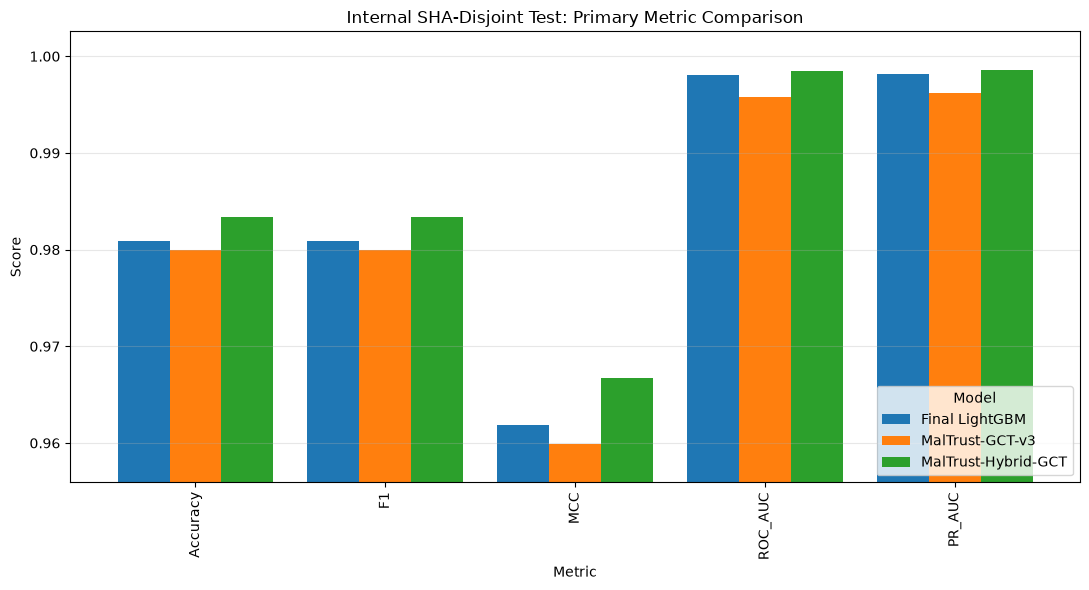

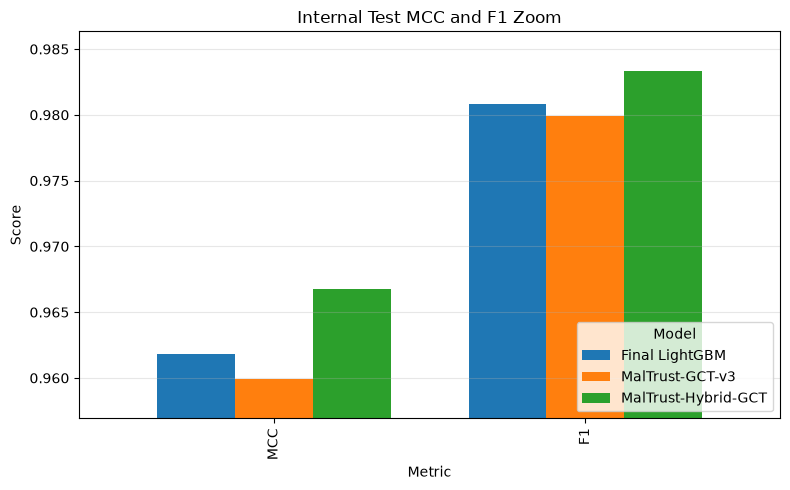

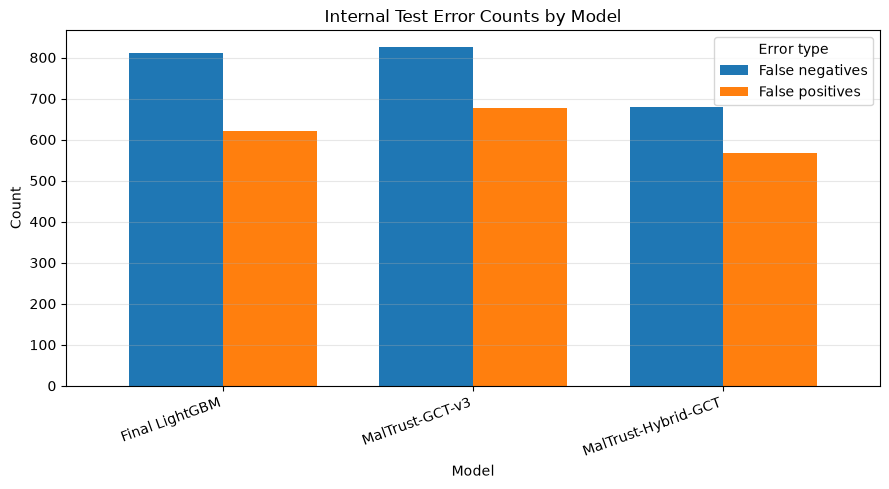

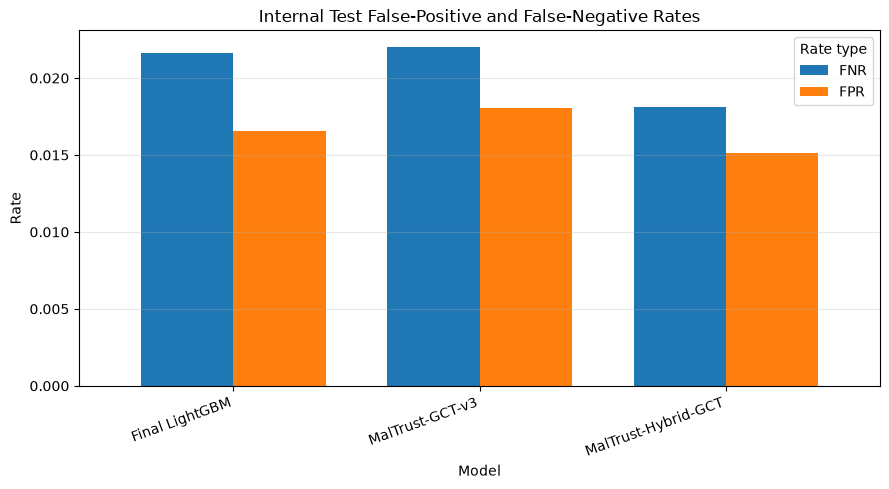

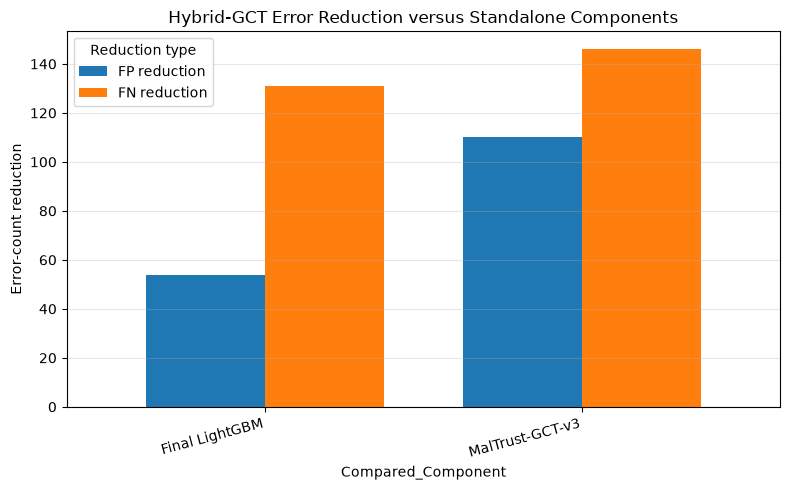

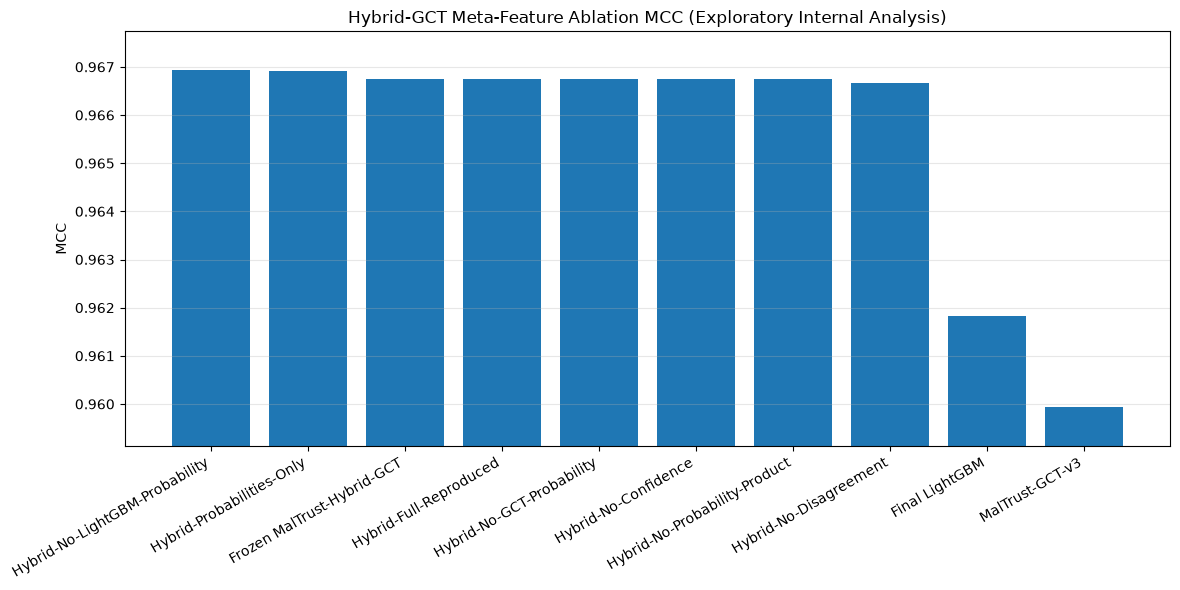


Hybrid-GCT manuscript figure inventory:


,Figure_ID,Figure_Name,Figure_Path,Figure_Type,Claim_Boundary
0,1,cell27_hybrid_gct_primary_metric_comparison.png,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,primary_metric_comparison,Internal SHA-disjoint held-out test only; no e...
1,2,cell27_hybrid_gct_mcc_f1_zoom_comparison.png,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,mcc_f1_zoom_comparison,Internal SHA-disjoint held-out test only; no e...
2,3,cell27_hybrid_gct_false_positive_false_negativ...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,fp_fn_count_comparison,Internal SHA-disjoint held-out test only; no e...
3,4,cell27_hybrid_gct_fpr_fnr_rate_comparison.png,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,fpr_fnr_rate_comparison,Internal SHA-disjoint held-out test only; no e...
4,5,cell27_hybrid_gct_error_reduction_vs_component...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,component_error_reduction,Internal paired component comparison only; no ...
5,6,cell27_hybrid_gct_meta_ablation_mcc_comparison...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,meta_ablation_mcc_comparison,Exploratory internal ablation only; ablated va...



Hybrid-GCT figure claim-boundary table:


,Claim_Type,Claim,Allowed,Evidence_Source
0,Allowed internal figure claim,Figures may show MalTrust-Hybrid-GCT as the be...,True,"Corrected Cells 18, 20, 21, 23, and 25"
1,Allowed error-analysis claim,Figures may report internal FP/FN and FPR/FNR ...,True,"Corrected Cells 18, 20, and 21"
2,Allowed ablation-figure claim,Ablation figures may show meta-feature robustn...,True,Corrected Cells 20 and 21
3,Not allowed external figure claim,Do not use these figures to claim external Hyb...,False,External Stage 3 pending



Post-Cell-27 experiment configuration snapshot saved to: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\figures\cell27_hybrid_gct_metric_error_analysis\revised_strict_clean_699\Top_699_All\configs\cell27_experiment_config_snapshot.json
Post-Cell-27 experiment configuration snapshot SHA-256: 0b0d1f60e9e6c856ca52b1b4572155213827c451b8b98843bc24d70bc3990a76

Cell 27 completed successfully.
Purpose: Hybrid-GCT manuscript-ready internal metric and error-analysis figures
Figures created: 6
Figure inventory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\figures\cell27_hybrid_gct_metric_error_analysis\revised_strict_clean_699\Top_699_All\tables\cell27_hybrid_gct_figure_inventory.csv
Internal metric table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\cell5_framework_artifacts\figures\cell27_hybrid_gct_metric_error_analysis\revised_strict_clean_699\Top_699_All\tables\cell27_hybrid_gct_internal_metric_comparison_table.csv
Error-analysis table: 

In [47]:
# ============================================================
# MalTrust-XAI | Cell 27
# Hybrid-GCT Manuscript-Ready Internal Metric and Error Figures
#
# Corrected for the current MalTrust-Hybrid-GCT pipeline:
# - Uses corrected Cells 18-25 Hybrid-GCT evidence objects
# - Does not use old generic LightGBM-only final_proposed_results_df logic
# - Does not create external-validation figures unless real external Hybrid-GCT
#   validation is present
# - Keeps figure claims internal and SHA-disjoint unless External Stage 3 exists
# - Saves tables, figures, claim-boundary metadata, hashes, and artifact index
# ============================================================

try:
    debug("Generating Hybrid-GCT manuscript-ready metric and error-analysis figures...")
except Exception:
    def debug(msg):
        print(f"[DEBUG] {msg}")
    debug("Generating Hybrid-GCT manuscript-ready metric and error-analysis figures...")

import os
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone


# ------------------------------------------------
# Timestamp / JSON / hash helpers
# ------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha.update(chunk)
    return sha.hexdigest()


def hash_file(path):
    if "sha256_file" in globals() and callable(globals()["sha256_file"]):
        try:
            return globals()["sha256_file"](path)
        except Exception:
            return sha256_file_local(path)
    return sha256_file_local(path)


# ------------------------------------------------
# Preconditions
# ------------------------------------------------
required_globals = [
    "FRAMEWORK_ARTIFACT_DIR",
    "EXPERIMENT_CONFIG"
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Required framework objects are missing: {missing_globals}")

if not os.path.exists(FRAMEWORK_ARTIFACT_DIR):
    raise FileNotFoundError(f"FRAMEWORK_ARTIFACT_DIR not found: {FRAMEWORK_ARTIFACT_DIR}")


# ------------------------------------------------
# Dynamic context
# ------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

FINAL_FEATURE_SET_NAME = (
    str(final_subset_name)
    if "final_subset_name" in globals()
    else str(
        EXPERIMENT_CONFIG.get(
            "cell15_final_subset",
            EXPERIMENT_CONFIG.get("cell11_selected_final_subset", "Top_699_All")
        )
    )
)

NUM_TRAIN_FILES_CELL27 = int(
    EXPERIMENT_CONFIG.get(
        "cell5_selected_train_files",
        EXPERIMENT_CONFIG.get("active_train_files", 50)
    )
)

EXPECTED_TOTAL_ROWS = int(
    EXPERIMENT_CONFIG.get(
        "expected_unique_sha256_after_dedup",
        NUM_TRAIN_FILES_CELL27 * 10000
    )
)

CELL27_ARTIFACT_DIR = os.path.join(
    FRAMEWORK_ARTIFACT_DIR,
    "figures",
    "cell27_hybrid_gct_metric_error_analysis",
    FINAL_FEATURE_SPACE_NAME,
    FINAL_FEATURE_SET_NAME
)

CELL27_TABLE_DIR = os.path.join(CELL27_ARTIFACT_DIR, "tables")
CELL27_FIGURE_DIR = os.path.join(CELL27_ARTIFACT_DIR, "figures")
CELL27_REPORT_DIR = os.path.join(CELL27_ARTIFACT_DIR, "reports")
CELL27_CONFIG_DIR = os.path.join(CELL27_ARTIFACT_DIR, "configs")

for directory in [CELL27_ARTIFACT_DIR, CELL27_TABLE_DIR, CELL27_FIGURE_DIR, CELL27_REPORT_DIR, CELL27_CONFIG_DIR]:
    os.makedirs(directory, exist_ok=True)

print("Cell 27 context:")
print("Purpose: Hybrid-GCT manuscript-ready internal metric and error-analysis figures")
print("Framework: MalTrust-Hybrid-GCT")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Final subset:", FINAL_FEATURE_SET_NAME)
print("Expected unique dataset size:", EXPECTED_TOTAL_ROWS)
print("Artifact directory:", CELL27_ARTIFACT_DIR)


# ------------------------------------------------
# Table resolution helpers
# ------------------------------------------------
def normalize_metric_columns(df):
    df = df.copy()
    rename_map = {
        "Recall": "Recall_TPR",
        "TPR": "Recall_TPR",
        "F1_Score": "F1",
        "Specificity": "Specificity_TNR",
        "TNR": "Specificity_TNR",
        "FPR": "False_Positive_Rate",
        "FNR": "False_Negative_Rate",
        "Brier": "Brier_Score",
        "Model_Name": "Model"
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]
    return df


def read_csv_if_exists(path):
    if path and isinstance(path, str) and os.path.exists(path):
        return pd.read_csv(path)
    return None


def resolve_dataframe(global_candidates=None, config_path_keys=None, label="table"):
    global_candidates = global_candidates or []
    config_path_keys = config_path_keys or []

    for name in global_candidates:
        if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
            return globals()[name].copy(), f"in_memory_{name}"

    for key in config_path_keys:
        path = EXPERIMENT_CONFIG.get(key, None)
        df = read_csv_if_exists(path)
        if df is not None and not df.empty:
            return df, path

    return pd.DataFrame(), "not_available"


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def model_label_series(df):
    model_col = first_existing_column(df, ["Model", "Variant", "Compared_Component", "Name"])
    if model_col is None:
        return pd.Series([""] * len(df), index=df.index)
    return df[model_col].astype(str)


def filter_internal_final_rows(df):
    if df is None or df.empty:
        return pd.DataFrame()

    temp = normalize_metric_columns(df.copy())
    labels = model_label_series(temp)
    wanted_patterns = [
        "MalTrust-Hybrid-GCT",
        "Frozen MalTrust-Hybrid-GCT",
        "Final LightGBM",
        "MalTrust-GCT-v3"
    ]

    mask = pd.Series(False, index=temp.index)
    for pattern in wanted_patterns:
        mask = mask | labels.str.contains(pattern, case=False, regex=False, na=False)

    # Prefer the Cell 18 final model comparison rows if Experiment_Type exists.
    if "Experiment_Type" in temp.columns:
        final_mask = temp["Experiment_Type"].astype(str).str.contains(
            "Final internal model comparison", case=False, regex=False, na=False
        )
        if (mask & final_mask).any():
            temp = temp[mask & final_mask].copy()
        else:
            temp = temp[mask].copy()
    else:
        temp = temp[mask].copy()

    if temp.empty:
        return temp

    if "Model" not in temp.columns:
        if "Variant" in temp.columns:
            temp["Model"] = temp["Variant"]
        else:
            temp["Model"] = model_label_series(temp)

    # Standardize the retained Hybrid label.
    temp["Model"] = temp["Model"].astype(str).replace({
        "Frozen MalTrust-Hybrid-GCT": "MalTrust-Hybrid-GCT"
    })
    if "Variant" not in temp.columns:
        temp["Variant"] = temp["Model"]

    # Remove duplicate model rows, preferring rows with the most metrics populated.
    metric_cols = ["Accuracy", "Balanced_Accuracy", "Precision", "Recall_TPR", "Specificity_TNR", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE", "TN", "FP", "FN", "TP"]
    present_metric_cols = [c for c in metric_cols if c in temp.columns]
    if present_metric_cols:
        temp["_metric_non_null_count"] = temp[present_metric_cols].notna().sum(axis=1)
        temp = temp.sort_values("_metric_non_null_count", ascending=False)
    temp = temp.drop_duplicates(subset=["Model"], keep="first").copy()
    if "_metric_non_null_count" in temp.columns:
        temp = temp.drop(columns=["_metric_non_null_count"])

    model_order = {"MalTrust-Hybrid-GCT": 1, "Final LightGBM": 2, "MalTrust-GCT-v3": 3}
    temp["_model_order"] = temp["Model"].map(model_order).fillna(99)
    temp = temp.sort_values("_model_order").drop(columns=["_model_order"]).reset_index(drop=True)
    return temp


# ------------------------------------------------
# Resolve corrected evidence sources
# ------------------------------------------------
final_metric_candidates, final_metric_source = resolve_dataframe(
    global_candidates=[
        "final_metric_comparison_plot_df",
        "in_memory_final_metric_comparison_plot_df",
        "cell18_final_metric_comparison_df",
        "final_internal_metric_comparison_df",
        "final_consolidated_evidence_df",
        "manuscript_consolidated_comparison_df"
    ],
    config_path_keys=[
        "cell18_final_metric_comparison_table_path",
        "cell18_metric_comparison_table_path",
        "cell18_manuscript_metric_table_path",
        "cell23_full_consolidated_evidence_table_path",
        "cell23_manuscript_consolidated_table_path"
    ],
    label="final metric comparison"
)

final_metric_df = filter_internal_final_rows(final_metric_candidates)

if final_metric_df.empty:
    raise FileNotFoundError(
        "Could not resolve the corrected final internal Hybrid-GCT metric comparison table. "
        "Run corrected Cell 18 or corrected Cell 23 before Cell 27."
    )

for col in ["Accuracy", "Balanced_Accuracy", "Precision", "Recall_TPR", "Specificity_TNR", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE", "False_Positive_Rate", "False_Negative_Rate", "TN", "FP", "FN", "TP"]:
    if col in final_metric_df.columns:
        final_metric_df[col] = pd.to_numeric(final_metric_df[col], errors="coerce")

if "Feature_Count" not in final_metric_df.columns:
    final_metric_df["Feature_Count"] = 699
final_metric_df["Feature_Count"] = pd.to_numeric(final_metric_df["Feature_Count"], errors="coerce").fillna(699).astype(int)

if "Testing_Samples" not in final_metric_df.columns:
    final_metric_df["Testing_Samples"] = 75000
final_metric_df["Testing_Samples"] = pd.to_numeric(final_metric_df["Testing_Samples"], errors="coerce").fillna(75000).astype(int)

print("Final internal metric source:", final_metric_source)
print("Final internal metric rows:", len(final_metric_df))

ablation_metrics_df, ablation_metrics_source = resolve_dataframe(
    global_candidates=[
        "hybrid_gct_ablation_metrics_df",
        "in_memory_hybrid_gct_ablation_metrics_df",
        "hybrid_gct_manuscript_ablation_summary_df",
        "evidence_backed_manuscript_ablation_df"
    ],
    config_path_keys=[
        "cell20_hybrid_gct_ablation_metrics_path",
        "cell20_ablation_metrics_path",
        "cell21_manuscript_ablation_table_path",
        "cell21_hybrid_gct_manuscript_ablation_summary_path"
    ],
    label="Hybrid-GCT ablation metrics"
)

ablation_metrics_df = normalize_metric_columns(ablation_metrics_df)
print("Ablation metric source:", ablation_metrics_source)

component_contribution_df, component_contribution_source = resolve_dataframe(
    global_candidates=[
        "hybrid_gct_component_contribution_summary_df",
        "in_memory_hybrid_gct_component_contribution_summary_df",
        "component_contribution_summary_df"
    ],
    config_path_keys=[
        "cell21_component_contribution_summary_path",
        "cell21_hybrid_gct_component_contribution_summary_path"
    ],
    label="Hybrid-GCT component contribution"
)
print("Component contribution source:", component_contribution_source)


# ------------------------------------------------
# Derived tables for figures
# ------------------------------------------------
primary_metric_cols = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE"]
available_primary_metrics = [c for c in primary_metric_cols if c in final_metric_df.columns]

if not {"MCC", "F1", "ROC_AUC"}.issubset(set(final_metric_df.columns)):
    raise ValueError("Final metric table must include at least MCC, F1, and ROC_AUC for manuscript figures.")

metric_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_internal_metric_comparison_table.csv")
final_metric_df.to_csv(metric_table_path, index=False)

# Error count/rate table.
required_error_cols = ["TN", "FP", "FN", "TP"]
missing_error_cols = [c for c in required_error_cols if c not in final_metric_df.columns]
if missing_error_cols:
    raise ValueError(f"Final metric table missing required error-analysis columns: {missing_error_cols}")

error_rows = []
for _, row in final_metric_df.iterrows():
    model = str(row["Model"])
    tn = int(row["TN"])
    fp = int(row["FP"])
    fn = int(row["FN"])
    tp = int(row["TP"])
    benign_total = tn + fp
    malware_total = tp + fn
    error_rows.append({
        "Model": model,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Benign_Total": benign_total,
        "Malware_Total": malware_total,
        "False_Positive_Rate": fp / benign_total if benign_total > 0 else np.nan,
        "False_Negative_Rate": fn / malware_total if malware_total > 0 else np.nan,
        "Specificity_TNR": tn / benign_total if benign_total > 0 else np.nan,
        "Recall_TPR": tp / malware_total if malware_total > 0 else np.nan
    })

error_analysis_df = pd.DataFrame(error_rows)
error_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_error_analysis_table.csv")
error_analysis_df.to_csv(error_table_path, index=False)

# Component reduction table from Cell 21 if available, otherwise compute directly.
if component_contribution_df is not None and not component_contribution_df.empty:
    component_table_df = component_contribution_df.copy()
else:
    hybrid_row = final_metric_df[final_metric_df["Model"].eq("MalTrust-Hybrid-GCT")].iloc[0]
    component_rows = []
    for component_name in ["Final LightGBM", "MalTrust-GCT-v3"]:
        comp_matches = final_metric_df[final_metric_df["Model"].eq(component_name)]
        if comp_matches.empty:
            continue
        comp = comp_matches.iloc[0]
        component_rows.append({
            "Compared_Component": component_name,
            "Frozen_Hybrid_MCC": hybrid_row.get("MCC", np.nan),
            "Component_MCC": comp.get("MCC", np.nan),
            "Delta_MCC_Hybrid_minus_Component": hybrid_row.get("MCC", np.nan) - comp.get("MCC", np.nan),
            "Frozen_Hybrid_F1": hybrid_row.get("F1", np.nan),
            "Component_F1": comp.get("F1", np.nan),
            "Delta_F1_Hybrid_minus_Component": hybrid_row.get("F1", np.nan) - comp.get("F1", np.nan),
            "Frozen_Hybrid_ROC_AUC": hybrid_row.get("ROC_AUC", np.nan),
            "Component_ROC_AUC": comp.get("ROC_AUC", np.nan),
            "Delta_ROC_AUC_Hybrid_minus_Component": hybrid_row.get("ROC_AUC", np.nan) - comp.get("ROC_AUC", np.nan),
            "Frozen_Hybrid_FP": int(hybrid_row.get("FP", 0)),
            "Component_FP": int(comp.get("FP", 0)),
            "FP_Reduction_Hybrid_vs_Component": int(comp.get("FP", 0)) - int(hybrid_row.get("FP", 0)),
            "Frozen_Hybrid_FN": int(hybrid_row.get("FN", 0)),
            "Component_FN": int(comp.get("FN", 0)),
            "FN_Reduction_Hybrid_vs_Component": int(comp.get("FN", 0)) - int(hybrid_row.get("FN", 0))
        })
    component_table_df = pd.DataFrame(component_rows)

component_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_component_error_reduction_table.csv")
component_table_df.to_csv(component_table_path, index=False)

# Clean ablation table for plotting.
ablation_plot_df = pd.DataFrame()
if ablation_metrics_df is not None and not ablation_metrics_df.empty:
    ablation_plot_df = ablation_metrics_df.copy()
    if "Model" not in ablation_plot_df.columns:
        if "Variant" in ablation_plot_df.columns:
            ablation_plot_df["Model"] = ablation_plot_df["Variant"]
        elif "Ablation_Setting" in ablation_plot_df.columns:
            ablation_plot_df["Model"] = ablation_plot_df["Ablation_Setting"]
    if "MCC" not in ablation_plot_df.columns and "MCC_Mean" in ablation_plot_df.columns:
        ablation_plot_df["MCC"] = ablation_plot_df["MCC_Mean"]
    if "F1" not in ablation_plot_df.columns and "F1_Mean" in ablation_plot_df.columns:
        ablation_plot_df["F1"] = ablation_plot_df["F1_Mean"]
    if "ROC_AUC" not in ablation_plot_df.columns and "ROC_AUC_Mean" in ablation_plot_df.columns:
        ablation_plot_df["ROC_AUC"] = ablation_plot_df["ROC_AUC_Mean"]
    if "Feature_Count" not in ablation_plot_df.columns:
        if "Meta_Feature_Count" in ablation_plot_df.columns:
            ablation_plot_df["Feature_Count"] = ablation_plot_df["Meta_Feature_Count"]
    if "MCC" in ablation_plot_df.columns:
        ablation_plot_df["MCC"] = pd.to_numeric(ablation_plot_df["MCC"], errors="coerce")
        ablation_plot_df = ablation_plot_df[ablation_plot_df["MCC"].notna()].copy()
        ablation_plot_df = ablation_plot_df.sort_values("MCC", ascending=False).reset_index(drop=True)

ablation_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_ablation_metric_plot_table.csv")
ablation_plot_df.to_csv(ablation_table_path, index=False)


# ------------------------------------------------
# Figure styling helpers
# ------------------------------------------------
def save_current_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def set_y_limits_tight(values, padding=0.003, lower_floor=0.0, upper_ceiling=1.02):
    values = pd.Series(values).dropna().astype(float)
    if values.empty:
        return
    ymin = max(lower_floor, float(values.min()) - padding)
    ymax = min(upper_ceiling, float(values.max()) + padding)
    if ymax <= ymin:
        ymax = ymin + padding * 2
    plt.ylim(ymin, ymax)


# ------------------------------------------------
# Create manuscript figures
# ------------------------------------------------
figure_records = []

# Figure 1: primary metric grouped comparison.
metric_long_rows = []
primary_plot_metrics = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC"]
for _, row in final_metric_df.iterrows():
    for metric in primary_plot_metrics:
        if metric in final_metric_df.columns and pd.notna(row.get(metric, np.nan)):
            metric_long_rows.append({
                "Model": row["Model"],
                "Metric": metric,
                "Value": float(row[metric])
            })
metric_long_df = pd.DataFrame(metric_long_rows)
metric_long_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_primary_metric_long_table.csv")
metric_long_df.to_csv(metric_long_table_path, index=False)

primary_metric_figure_path = os.path.join(CELL27_FIGURE_DIR, "cell27_hybrid_gct_primary_metric_comparison.png")
if not metric_long_df.empty:
    pivot = metric_long_df.pivot(index="Metric", columns="Model", values="Value").reindex(primary_plot_metrics)
    ax = pivot.plot(kind="bar", figsize=(11, 6), width=0.82)
    ax.set_ylabel("Score")
    ax.set_title("Internal SHA-Disjoint Test: Primary Metric Comparison")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Model", loc="lower right")
    set_y_limits_tight(metric_long_df["Value"], padding=0.004, lower_floor=0.94, upper_ceiling=1.005)
    save_current_figure(primary_metric_figure_path)
    figure_records.append({
        "Figure_Name": os.path.basename(primary_metric_figure_path),
        "Figure_Path": primary_metric_figure_path,
        "Figure_Type": "primary_metric_comparison",
        "Claim_Boundary": "Internal SHA-disjoint held-out test only; no external claim."
    })

# Figure 2: MCC/F1 zoom.
zoom_metric_rows = metric_long_df[metric_long_df["Metric"].isin(["MCC", "F1"])].copy()
zoom_metric_figure_path = os.path.join(CELL27_FIGURE_DIR, "cell27_hybrid_gct_mcc_f1_zoom_comparison.png")
if not zoom_metric_rows.empty:
    pivot = zoom_metric_rows.pivot(index="Metric", columns="Model", values="Value").reindex(["MCC", "F1"])
    ax = pivot.plot(kind="bar", figsize=(8, 5), width=0.75)
    ax.set_ylabel("Score")
    ax.set_title("Internal Test MCC and F1 Zoom")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Model", loc="lower right")
    set_y_limits_tight(zoom_metric_rows["Value"], padding=0.003, lower_floor=0.94, upper_ceiling=1.005)
    save_current_figure(zoom_metric_figure_path)
    figure_records.append({
        "Figure_Name": os.path.basename(zoom_metric_figure_path),
        "Figure_Path": zoom_metric_figure_path,
        "Figure_Type": "mcc_f1_zoom_comparison",
        "Claim_Boundary": "Internal SHA-disjoint held-out test only; no external claim."
    })

# Figure 3: FP/FN counts.
error_count_long = error_analysis_df.melt(
    id_vars=["Model"],
    value_vars=["FP", "FN"],
    var_name="Error_Type",
    value_name="Count"
)
error_count_long["Error_Type"] = error_count_long["Error_Type"].replace({"FP": "False positives", "FN": "False negatives"})
error_count_long_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_error_count_long_table.csv")
error_count_long.to_csv(error_count_long_table_path, index=False)

error_count_figure_path = os.path.join(CELL27_FIGURE_DIR, "cell27_hybrid_gct_false_positive_false_negative_counts.png")
pivot = error_count_long.pivot(index="Model", columns="Error_Type", values="Count")
ax = pivot.plot(kind="bar", figsize=(9, 5), width=0.75)
ax.set_ylabel("Count")
ax.set_title("Internal Test Error Counts by Model")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Error type")
plt.xticks(rotation=20, ha="right")
save_current_figure(error_count_figure_path)
figure_records.append({
    "Figure_Name": os.path.basename(error_count_figure_path),
    "Figure_Path": error_count_figure_path,
    "Figure_Type": "fp_fn_count_comparison",
    "Claim_Boundary": "Internal SHA-disjoint held-out test only; no external claim."
})

# Figure 4: FPR/FNR rates.
error_rate_long = error_analysis_df.melt(
    id_vars=["Model"],
    value_vars=["False_Positive_Rate", "False_Negative_Rate"],
    var_name="Rate_Type",
    value_name="Rate"
)
error_rate_long["Rate_Type"] = error_rate_long["Rate_Type"].replace({
    "False_Positive_Rate": "FPR",
    "False_Negative_Rate": "FNR"
})
error_rate_long_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_error_rate_long_table.csv")
error_rate_long.to_csv(error_rate_long_table_path, index=False)

error_rate_figure_path = os.path.join(CELL27_FIGURE_DIR, "cell27_hybrid_gct_fpr_fnr_rate_comparison.png")
pivot = error_rate_long.pivot(index="Model", columns="Rate_Type", values="Rate")
ax = pivot.plot(kind="bar", figsize=(9, 5), width=0.75)
ax.set_ylabel("Rate")
ax.set_title("Internal Test False-Positive and False-Negative Rates")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Rate type")
plt.xticks(rotation=20, ha="right")
save_current_figure(error_rate_figure_path)
figure_records.append({
    "Figure_Name": os.path.basename(error_rate_figure_path),
    "Figure_Path": error_rate_figure_path,
    "Figure_Type": "fpr_fnr_rate_comparison",
    "Claim_Boundary": "Internal SHA-disjoint held-out test only; no external claim."
})

# Figure 5: Hybrid error reduction vs components.
reduction_figure_path = os.path.join(CELL27_FIGURE_DIR, "cell27_hybrid_gct_error_reduction_vs_components.png")
if not component_table_df.empty:
    component_plot_df = component_table_df.copy()
    if "Compared_Component" not in component_plot_df.columns and "Component" in component_plot_df.columns:
        component_plot_df["Compared_Component"] = component_plot_df["Component"]
    reduction_cols = ["FP_Reduction_Hybrid_vs_Component", "FN_Reduction_Hybrid_vs_Component"]
    if all(c in component_plot_df.columns for c in reduction_cols) and "Compared_Component" in component_plot_df.columns:
        plot_df = component_plot_df[["Compared_Component"] + reduction_cols].copy()
        plot_df = plot_df.set_index("Compared_Component")
        plot_df = plot_df.rename(columns={
            "FP_Reduction_Hybrid_vs_Component": "FP reduction",
            "FN_Reduction_Hybrid_vs_Component": "FN reduction"
        })
        ax = plot_df.plot(kind="bar", figsize=(8, 5), width=0.75)
        ax.set_ylabel("Error-count reduction")
        ax.set_title("Hybrid-GCT Error Reduction versus Standalone Components")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Reduction type")
        plt.xticks(rotation=15, ha="right")
        save_current_figure(reduction_figure_path)
        figure_records.append({
            "Figure_Name": os.path.basename(reduction_figure_path),
            "Figure_Path": reduction_figure_path,
            "Figure_Type": "component_error_reduction",
            "Claim_Boundary": "Internal paired component comparison only; no external claim."
        })

# Figure 6: ablation MCC near-parity.
ablation_mcc_figure_path = os.path.join(CELL27_FIGURE_DIR, "cell27_hybrid_gct_meta_ablation_mcc_comparison.png")
if ablation_plot_df is not None and not ablation_plot_df.empty and "MCC" in ablation_plot_df.columns and "Model" in ablation_plot_df.columns:
    plot_df = ablation_plot_df.copy()
    # Keep only rows with real MCC and not too many labels.
    plot_df = plot_df[plot_df["MCC"].notna()].copy()
    plot_df = plot_df.sort_values("MCC", ascending=False).head(12)
    if not plot_df.empty:
        plt.figure(figsize=(12, 6))
        plt.bar(plot_df["Model"].astype(str), plot_df["MCC"].astype(float))
        plt.ylabel("MCC")
        plt.title("Hybrid-GCT Meta-Feature Ablation MCC (Exploratory Internal Analysis)")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)
        set_y_limits_tight(plot_df["MCC"], padding=0.0008, lower_floor=0.958, upper_ceiling=0.969)
        save_current_figure(ablation_mcc_figure_path)
        figure_records.append({
            "Figure_Name": os.path.basename(ablation_mcc_figure_path),
            "Figure_Path": ablation_mcc_figure_path,
            "Figure_Type": "meta_ablation_mcc_comparison",
            "Claim_Boundary": "Exploratory internal ablation only; ablated variants are not replacement final models."
        })
else:
    print("Hybrid-GCT ablation metrics unavailable; skipping ablation MCC figure.")


# ------------------------------------------------
# Claim-boundary table
# ------------------------------------------------
external_hybrid_gct_validated = bool(
    EXPERIMENT_CONFIG.get("cell23_external_hybrid_gct_validation_included", False)
    or EXPERIMENT_CONFIG.get("cell23_external_validation_included", False)
    or EXPERIMENT_CONFIG.get("external_hybrid_gct_validation_completed", False)
    or EXPERIMENT_CONFIG.get("external_hybrid_gct_validation_included", False)
)

claim_boundary_df = pd.DataFrame([
    {
        "Claim_Type": "Allowed internal figure claim",
        "Claim": "Figures may show MalTrust-Hybrid-GCT as the best retained model on the internal SHA-disjoint held-out test.",
        "Allowed": True,
        "Evidence_Source": "Corrected Cells 18, 20, 21, 23, and 25",
    },
    {
        "Claim_Type": "Allowed error-analysis claim",
        "Claim": "Figures may report internal FP/FN and FPR/FNR reductions versus standalone Final LightGBM and GCT-v3.",
        "Allowed": True,
        "Evidence_Source": "Corrected Cells 18, 20, and 21",
    },
    {
        "Claim_Type": "Allowed ablation-figure claim",
        "Claim": "Ablation figures may show meta-feature robustness and near-parity behavior but must not replace the frozen final Hybrid-GCT model.",
        "Allowed": True,
        "Evidence_Source": "Corrected Cells 20 and 21",
    },
    {
        "Claim_Type": "Not allowed external figure claim",
        "Claim": "Do not use these figures to claim external Hybrid-GCT superiority before External Stage 3 is completed.",
        "Allowed": bool(external_hybrid_gct_validated),
        "Evidence_Source": "External Stage 3 pending" if not external_hybrid_gct_validated else "External Hybrid-GCT validation artifact detected",
    }
])

claim_boundary_table_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_figure_claim_boundary_table.csv")
claim_boundary_df.to_csv(claim_boundary_table_path, index=False)


# ------------------------------------------------
# Figure inventory and report
# ------------------------------------------------
figure_inventory_df = pd.DataFrame(figure_records)
if not figure_inventory_df.empty:
    figure_inventory_df.insert(0, "Figure_ID", np.arange(1, len(figure_inventory_df) + 1))
else:
    figure_inventory_df = pd.DataFrame(columns=["Figure_ID", "Figure_Name", "Figure_Path", "Figure_Type", "Claim_Boundary"])

figure_inventory_path = os.path.join(CELL27_TABLE_DIR, "cell27_hybrid_gct_figure_inventory.csv")
figure_inventory_df.to_csv(figure_inventory_path, index=False)

print("\nHybrid-GCT manuscript figure inventory:")
display(figure_inventory_df)

print("\nHybrid-GCT figure claim-boundary table:")
display(claim_boundary_df)

cell27_report_path = os.path.join(CELL27_REPORT_DIR, "cell27_hybrid_gct_metric_error_analysis_report.json")
cell27_report = {
    "cell": "Cell 27",
    "cell_name": "Hybrid-GCT Manuscript-Ready Internal Metric and Error Figures",
    "framework": "MalTrust-Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "selected_train_files": int(NUM_TRAIN_FILES_CELL27),
    "expected_total_deduplicated_rows": int(EXPECTED_TOTAL_ROWS),
    "final_metric_source": final_metric_source,
    "ablation_metric_source": ablation_metrics_source,
    "component_contribution_source": component_contribution_source,
    "figure_count": int(len(figure_inventory_df)),
    "external_hybrid_gct_validated": bool(external_hybrid_gct_validated),
    "analysis_policy": (
        "Figures are internal SHA-disjoint held-out-test and exploratory ablation figures only. "
        "They must not be used to claim external Hybrid-GCT superiority until External Stage 3 is complete."
    ),
    "metric_table_path": metric_table_path,
    "error_table_path": error_table_path,
    "component_error_reduction_table_path": component_table_path,
    "ablation_plot_table_path": ablation_table_path,
    "claim_boundary_table_path": claim_boundary_table_path,
    "figure_inventory_path": figure_inventory_path,
    "figures": figure_records,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}
save_json(cell27_report, cell27_report_path)


# ------------------------------------------------
# Artifact hashes and index
# ------------------------------------------------
cell27_artifacts = {
    "internal_metric_comparison_table": metric_table_path,
    "primary_metric_long_table": metric_long_table_path,
    "error_analysis_table": error_table_path,
    "error_count_long_table": error_count_long_table_path,
    "error_rate_long_table": error_rate_long_table_path,
    "component_error_reduction_table": component_table_path,
    "ablation_metric_plot_table": ablation_table_path,
    "figure_claim_boundary_table": claim_boundary_table_path,
    "figure_inventory": figure_inventory_path,
    "metric_error_analysis_report": cell27_report_path,
}

for rec in figure_records:
    name = os.path.splitext(rec["Figure_Name"])[0]
    cell27_artifacts[f"figure_{name}"] = rec["Figure_Path"]

cell27_artifact_rows = []
for artifact_name, artifact_path in cell27_artifacts.items():
    if artifact_path is None or not os.path.exists(artifact_path):
        continue
    cell27_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": hash_file(artifact_path),
        "registered_at": now_str()
    })

cell27_artifact_hashes_path = os.path.join(CELL27_ARTIFACT_DIR, "cell27_hybrid_gct_artifact_hashes.csv")
pd.DataFrame(cell27_artifact_rows).to_csv(cell27_artifact_hashes_path, index=False)

cell27_artifact_index = {
    "cell": "Cell 27",
    "cell_name": "Hybrid-GCT Manuscript-Ready Internal Metric and Error Figures",
    "framework": "MalTrust-Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "final_selected_subset": FINAL_FEATURE_SET_NAME,
    "figure_count": int(len(figure_inventory_df)),
    "external_hybrid_gct_validated": bool(external_hybrid_gct_validated),
    "created_at_utc": utc_now_string(),
    "artifacts": cell27_artifact_rows,
    "artifact_hash_report_path": cell27_artifact_hashes_path,
    "artifact_hash_report_sha256": hash_file(cell27_artifact_hashes_path)
}

cell27_artifact_index_path = os.path.join(CELL27_ARTIFACT_DIR, "cell27_hybrid_gct_artifact_index.json")
save_json(cell27_artifact_index, cell27_artifact_index_path)
cell27_artifact_index_hash = hash_file(cell27_artifact_index_path)


# ------------------------------------------------
# Update experiment config
# ------------------------------------------------
try:
    EXPERIMENT_CONFIG["cell27_hybrid_gct_metric_table_path"] = metric_table_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_error_table_path"] = error_table_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_component_error_reduction_table_path"] = component_table_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_ablation_metric_plot_table_path"] = ablation_table_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_claim_boundary_table_path"] = claim_boundary_table_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_figure_inventory_path"] = figure_inventory_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_report_path"] = cell27_report_path
    EXPERIMENT_CONFIG["cell27_hybrid_gct_figure_count"] = int(len(figure_inventory_df))
    EXPERIMENT_CONFIG["cell27_external_hybrid_gct_validated"] = bool(external_hybrid_gct_validated)
    EXPERIMENT_CONFIG["cell27_artifact_index_path"] = cell27_artifact_index_path
    EXPERIMENT_CONFIG["cell27_artifact_index_sha256"] = cell27_artifact_index_hash

    post_cell27_config_path = os.path.join(CELL27_CONFIG_DIR, "cell27_experiment_config_snapshot.json")
    save_json(EXPERIMENT_CONFIG, post_cell27_config_path)
    post_cell27_config_hash = hash_file(post_cell27_config_path)
    EXPERIMENT_CONFIG["cell27_experiment_config_snapshot_path"] = post_cell27_config_path
    EXPERIMENT_CONFIG["cell27_experiment_config_snapshot_sha256"] = post_cell27_config_hash

    print("\nPost-Cell-27 experiment configuration snapshot saved to:", post_cell27_config_path)
    print("Post-Cell-27 experiment configuration snapshot SHA-256:", post_cell27_config_hash)
except Exception as e:
    print("EXPERIMENT_CONFIG update skipped or failed:", str(e))


# ------------------------------------------------
# Standard aliases
# ------------------------------------------------
hybrid_gct_metric_error_figure_inventory_df = figure_inventory_df
hybrid_gct_final_error_analysis_df = error_analysis_df
hybrid_gct_component_error_reduction_df = component_table_df
hybrid_gct_figure_claim_boundary_df = claim_boundary_df


# ------------------------------------------------
# Final summary and assertions
# ------------------------------------------------
print("\nCell 27 completed successfully.")
print("Purpose: Hybrid-GCT manuscript-ready internal metric and error-analysis figures")
print("Figures created:", len(figure_inventory_df))
print("Figure inventory:", figure_inventory_path)
print("Internal metric table:", metric_table_path)
print("Error-analysis table:", error_table_path)
print("Claim-boundary table:", claim_boundary_table_path)
print("Artifact index:", cell27_artifact_index_path)
print("Artifact index SHA-256:", cell27_artifact_index_hash)

assert not final_metric_df.empty, "Final metric comparison table is empty."
assert not error_analysis_df.empty, "Error-analysis table is empty."
assert os.path.exists(figure_inventory_path), "Figure inventory was not saved."
assert os.path.exists(cell27_report_path), "Cell 27 report was not saved."
assert len(figure_inventory_df) > 0, "No figures were created."

# Prevent accidental external claim before External Stage 3.
if not external_hybrid_gct_validated:
    external_claim_row = claim_boundary_df[claim_boundary_df["Claim_Type"].eq("Not allowed external figure claim")]
    assert not external_claim_row.empty, "External claim-boundary row is missing."
    assert external_claim_row.iloc[0]["Allowed"] is False or bool(external_claim_row.iloc[0]["Allowed"]) is False, (
        "External Hybrid-GCT figure claim must remain disallowed before External Stage 3."
    )

debug("Hybrid-GCT manuscript-ready metric and error-analysis figure cell completed successfully.")


## External Validity  
## PHASE 2

In [48]:
# # ============================================================
# MalTrust-XAI | External Validation Cell 1
# External/Independent EMBER2024 Win64 Test-Period Loader Setup
# File Discovery, Reproducibility Manifest, and Leakage Policy
#
# Purpose:
# - Prepare an independent validation source without touching main training files
# - Enforce consistency with the main framework:
#   final feature space = revised_strict_clean_699
# - Save external validation configuration and JSONL file fingerprints
# ============================================================

try:
    debug("Starting External Validation Cell 1: independent data discovery and configuration...")
except Exception:
    def debug(msg):
        print(f"[DEBUG] {msg}")
    debug("Starting External Validation Cell 1: independent data discovery and configuration...")

import os
import glob
import json
import hashlib
import platform
import sys
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Timestamp / save / hash helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def count_jsonl_rows(filepath):
    count = 0
    with open(filepath, "rb") as f:
        for _ in f:
            count += 1
    return count


# ------------------------------------------------------------
# Main-framework consistency checks
# ------------------------------------------------------------
FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

if "EXPERIMENT_CONFIG" in globals():
    MAIN_ARTIFACT_DIR = EXPERIMENT_CONFIG.get(
        "artifact_directory",
        globals().get("ARTIFACT_DIR", r"C:\\Users\\LENOVO\\Desktop\\Maltrust_xai_artifacts")
    )
    RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", 42))
else:
    EXPERIMENT_CONFIG = {}
    MAIN_ARTIFACT_DIR = globals().get(
        "ARTIFACT_DIR",
        r"C:\\Users\\LENOVO\\Desktop\\Maltrust_xai_artifacts"
    )
    RANDOM_STATE = 42

os.makedirs(MAIN_ARTIFACT_DIR, exist_ok=True)


# ------------------------------------------------------------
# External validation data configuration
# ------------------------------------------------------------
# IMPORTANT:
# This cell is configured to use the EMBER2024 Win64_test folder only.
# This is independent test-period validation relative to the 50 selected training files.
# It is not a separate external corpus like BODMAS.
#
# For BODMAS or another corpus, set EXTERNAL_SOURCE_MODE and EXTERNAL_DATA_ROOT
# in the later dataset-specific loader cell.

DATA_ROOT = r"C:\\Users\\LENOVO\\Desktop\\Maltrust-XAI_Framework\\data"
WIN64_TRAIN_PATH = os.path.join(DATA_ROOT, "Win64_train")
WIN64_TEST_PATH = os.path.join(DATA_ROOT, "Win64_test")

EXTERNAL_SOURCE_MODE = "ember2024_win64_test_period"
EXTERNAL_DATA_ROOT = WIN64_TEST_PATH

EXTERNAL_VALIDATION_ARTIFACT_DIR = os.path.join(
    MAIN_ARTIFACT_DIR,
    "external_validation",
    EXTERNAL_SOURCE_MODE,
    FINAL_FEATURE_SPACE_NAME
)

os.makedirs(EXTERNAL_VALIDATION_ARTIFACT_DIR, exist_ok=True)

# Full external evaluation by default.
# Use debug mode only if runtime testing is needed.
EXTERNAL_DEBUG_MODE = bool(EXPERIMENT_CONFIG.get("external_validation_debug_mode", False))

if EXTERNAL_DEBUG_MODE:
    MAX_TOTAL_ROWS = int(EXPERIMENT_CONFIG.get("external_validation_debug_max_rows", 50000))
    ROWS_PER_FILE = int(EXPERIMENT_CONFIG.get("external_validation_debug_rows_per_file", 5000))
else:
    MAX_TOTAL_ROWS = None
    ROWS_PER_FILE = None


# ------------------------------------------------------------
# Leakage and exclusion policy aligned with main framework
# ------------------------------------------------------------
TOP_LEVEL_EXCLUDED_COLUMNS_EXTERNAL = [
    "md5",
    "sha1",
    "sha256",
    "tlsh",
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio",
    "family",
    "family_confidence",
    "behavior",
    "caps",
    "ttps",
    "mbc",
    "packer",
    "exploit",
    "group",
    "pefilewarnings",
    "file_property",
    "file_type"
]

NESTED_LEAKAGE_PATHS_TO_EXCLUDE_EXTERNAL = [
    "header.coff.timestamp",
    "authenticode.latest_signing_time",
    "authenticode.signing_time_diff"
]

NESTED_LEAKAGE_FLATTENED_COLUMNS_EXTERNAL = [
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

LEAKAGE_FEATURE_COLUMNS_EXTERNAL = set([
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
])

LABEL_CANDIDATES = [
    "label",
    "y",
    "target",
    "malware",
    "is_malware"
]

RETAINED_STATIC_PE_GROUPS_EXTERNAL = [
    "histogram",
    "byteentropy",
    "strings",
    "general",
    "header",
    "section",
    "imports",
    "exports",
    "datadirectories",
    "richheader",
    "authenticode"
]


# ------------------------------------------------------------
# Discover external validation files
# ------------------------------------------------------------
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")

if not os.path.exists(EXTERNAL_DATA_ROOT):
    raise FileNotFoundError(f"External validation data root not found: {EXTERNAL_DATA_ROOT}")

main_train_files_detected = sorted(glob.glob(os.path.join(WIN64_TRAIN_PATH, "*.jsonl")))
external_jsonl_files = sorted(glob.glob(os.path.join(EXTERNAL_DATA_ROOT, "*.jsonl")))

if len(external_jsonl_files) == 0:
    raise FileNotFoundError(
        f"No external validation JSONL files found under: {EXTERNAL_DATA_ROOT}"
    )

# Hard safety check: external validation must not include files from Win64_train.
train_file_set = set(os.path.abspath(p) for p in main_train_files_detected)
external_file_set = set(os.path.abspath(p) for p in external_jsonl_files)
overlap_with_train_files = sorted(train_file_set.intersection(external_file_set))

if overlap_with_train_files:
    raise RuntimeError(
        "External validation file list overlaps with training files. "
        "This is not valid external/independent validation."
    )


# ------------------------------------------------------------
# File fingerprints and row counts
# ------------------------------------------------------------
fingerprint_rows = []

iterator = external_jsonl_files
if tqdm is not None:
    iterator = tqdm(external_jsonl_files, desc="Fingerprint external JSONL files", unit="file")

for idx, file_path in enumerate(iterator, start=1):
    file_size_bytes = os.path.getsize(file_path)
    file_sha256 = sha256_file_local(file_path)

    try:
        row_count = count_jsonl_rows(file_path)
    except Exception:
        row_count = None

    fingerprint_rows.append({
        "External_File_Index": int(idx),
        "File_Name": os.path.basename(file_path),
        "File_Path": os.path.abspath(file_path),
        "File_Size_Bytes": int(file_size_bytes),
        "File_Size_MB": round(file_size_bytes / (1024 ** 2), 3),
        "JSONL_Row_Count": row_count,
        "File_SHA256": file_sha256
    })

external_file_manifest_df = pd.DataFrame(fingerprint_rows)

external_total_raw_rows = int(
    external_file_manifest_df["JSONL_Row_Count"].dropna().sum()
)

if MAX_TOTAL_ROWS is None:
    planned_rows_for_validation = external_total_raw_rows
else:
    planned_rows_for_validation = min(int(MAX_TOTAL_ROWS), external_total_raw_rows)


# ------------------------------------------------------------
# Save manifests
# ------------------------------------------------------------
external_file_manifest_csv_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell1_file_manifest.csv"
)

external_file_manifest_json_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell1_file_manifest.json"
)

external_config_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell1_config.json"
)

external_artifact_index_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell1_artifact_index.json"
)

save_csv_atomic(external_file_manifest_df, external_file_manifest_csv_path, index=False)
save_json_atomic(
    {"external_file_manifest": external_file_manifest_df.to_dict("records")},
    external_file_manifest_json_path
)

external_validation_config = {
    "cell": "External Validation Cell 1",
    "purpose": "Independent/test-period external validation data discovery and reproducibility setup",
    "external_source_mode": EXTERNAL_SOURCE_MODE,
    "external_data_root": os.path.abspath(EXTERNAL_DATA_ROOT),
    "main_data_root": os.path.abspath(DATA_ROOT),
    "main_train_path": os.path.abspath(WIN64_TRAIN_PATH),
    "main_test_path": os.path.abspath(WIN64_TEST_PATH),
    "final_feature_space_name": FINAL_FEATURE_SPACE_NAME,
    "random_state": int(RANDOM_STATE),
    "external_debug_mode": bool(EXTERNAL_DEBUG_MODE),
    "max_total_rows": MAX_TOTAL_ROWS,
    "rows_per_file": ROWS_PER_FILE,
    "external_jsonl_file_count": int(len(external_jsonl_files)),
    "main_train_file_count_detected": int(len(main_train_files_detected)),
    "external_total_raw_rows": int(external_total_raw_rows),
    "planned_rows_for_validation": int(planned_rows_for_validation),
    "uses_main_training_files": False,
    "overlap_with_training_files_count": int(len(overlap_with_train_files)),
    "top_level_excluded_columns": TOP_LEVEL_EXCLUDED_COLUMNS_EXTERNAL,
    "nested_leakage_paths_to_exclude": NESTED_LEAKAGE_PATHS_TO_EXCLUDE_EXTERNAL,
    "nested_leakage_flattened_columns": NESTED_LEAKAGE_FLATTENED_COLUMNS_EXTERNAL,
    "leakage_feature_columns": sorted(LEAKAGE_FEATURE_COLUMNS_EXTERNAL),
    "retained_static_pe_groups": RETAINED_STATIC_PE_GROUPS_EXTERNAL,
    "label_candidates": LABEL_CANDIDATES,
    "artifact_directory": EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "python_version": sys.version,
    "platform": platform.platform(),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

save_json_atomic(external_validation_config, external_config_path)

external_file_manifest_csv_sha256 = sha256_file_local(external_file_manifest_csv_path)
external_file_manifest_json_sha256 = sha256_file_local(external_file_manifest_json_path)
external_config_sha256 = sha256_file_local(external_config_path)

external_artifact_index = {
    "cell": "External Validation Cell 1",
    "external_source_mode": EXTERNAL_SOURCE_MODE,
    "final_feature_space_name": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": {
        "file_manifest_csv": external_file_manifest_csv_path,
        "file_manifest_csv_sha256": external_file_manifest_csv_sha256,
        "file_manifest_json": external_file_manifest_json_path,
        "file_manifest_json_sha256": external_file_manifest_json_sha256,
        "external_validation_config": external_config_path,
        "external_validation_config_sha256": external_config_sha256
    }
}

save_json_atomic(external_artifact_index, external_artifact_index_path)
external_artifact_index_sha256 = sha256_file_local(external_artifact_index_path)


# ------------------------------------------------------------
# Update global config for later external-validation cells
# ------------------------------------------------------------
EXTERNAL_VALIDATION_CONFIG = external_validation_config
EXTERNAL_JSONL_FILES = external_jsonl_files

try:
    EXPERIMENT_CONFIG["external_validation_source_mode"] = EXTERNAL_SOURCE_MODE
    EXPERIMENT_CONFIG["external_validation_artifact_dir"] = EXTERNAL_VALIDATION_ARTIFACT_DIR
    EXPERIMENT_CONFIG["external_validation_file_manifest_csv_path"] = external_file_manifest_csv_path
    EXPERIMENT_CONFIG["external_validation_config_path"] = external_config_path
    EXPERIMENT_CONFIG["external_validation_cell1_artifact_index_path"] = external_artifact_index_path
    EXPERIMENT_CONFIG["external_validation_cell1_artifact_index_sha256"] = external_artifact_index_sha256
    EXPERIMENT_CONFIG["external_validation_raw_row_count"] = int(external_total_raw_rows)
    EXPERIMENT_CONFIG["external_validation_planned_rows"] = int(planned_rows_for_validation)
except Exception as e:
    print("Warning: could not update EXPERIMENT_CONFIG:", str(e))


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------
print("\nExternal Validation Cell 1 Summary")
print("----------------------------------")
print("External source mode:", EXTERNAL_SOURCE_MODE)
print("Final feature space:", FINAL_FEATURE_SPACE_NAME)
print("Data root:", DATA_ROOT)
print("External validation root:", EXTERNAL_DATA_ROOT)
print("Main train files detected:", len(main_train_files_detected))
print("External JSONL files:", len(external_jsonl_files))
print("External total raw rows:", external_total_raw_rows)
print("Planned validation rows:", planned_rows_for_validation)
print("Debug mode:", EXTERNAL_DEBUG_MODE)
print("Rows per file:", ROWS_PER_FILE)
print("Max total rows:", MAX_TOTAL_ROWS)
print("Overlap with training files:", len(overlap_with_train_files))
print("Artifact directory:", EXTERNAL_VALIDATION_ARTIFACT_DIR)
print("External config SHA-256:", external_config_sha256)
print("Cell 1 artifact index SHA-256:", external_artifact_index_sha256)

print("\nFirst external files:")
display(external_file_manifest_df.head())

assert len(external_jsonl_files) > 0, "No external validation files discovered."
assert len(overlap_with_train_files) == 0, "External validation overlaps with training files."
assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", "External validation must use revised strict-clean 699."

debug("External Validation Cell 1 completed successfully.")

[DEBUG] 2026-06-24 11:06:54 | Starting External Validation Cell 1: independent data discovery and configuration...


Fingerprint external JSONL files:   0%|          | 0/12 [00:00<?, ?file/s]


External Validation Cell 1 Summary
----------------------------------
External source mode: ember2024_win64_test_period
Final feature space: revised_strict_clean_699
Data root: C:\\Users\\LENOVO\\Desktop\\Maltrust-XAI_Framework\\data
External validation root: C:\\Users\\LENOVO\\Desktop\\Maltrust-XAI_Framework\\data\Win64_test
Main train files detected: 52
External JSONL files: 12
External total raw rows: 240000
Planned validation rows: 240000
Debug mode: False
Rows per file: None
Max total rows: None
Overlap with training files: 0
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699
External config SHA-256: 9de837a959e7ee32e43062df6f68ba0a2965fefb128bc4d6dac0b5dfa55e596c
Cell 1 artifact index SHA-256: 74efa53be11572c3b202b7b525c4cba571a0b4fb292c7052397a89f2d496846e

First external files:


,External_File_Index,File_Name,File_Path,File_Size_Bytes,File_Size_MB,JSONL_Row_Count,File_SHA256
0,1,2024-09-22_2024-09-28_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,482385466,460.039,20000,0391343fff5b8d1f310732f9950318d82c8c3d8bf55ac4...
1,2,2024-09-29_2024-10-05_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,447871748,427.124,20000,0f41c07914861135f66c53fe53a86e4660b861592a5797...
2,3,2024-10-06_2024-10-12_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,463854205,442.366,20000,4b7a0fbab6dbdce4b940b7f84d3cfdace56f175cafd143...
3,4,2024-10-13_2024-10-19_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,477021676,454.923,20000,872a5084172edca635d9f20407e5e049274fa526cb22fd...
4,5,2024-10-20_2024-10-26_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,464091283,442.592,20000,563c247bf2f7838a4edc4d46bf08b5f7583eff6658ed84...


[DEBUG] 2026-06-24 11:07:01 | External Validation Cell 1 completed successfully.


In [49]:
# ============================================================
# MalTrust-XAI | External Validation Cell 2 v2
# Same-Notebook Feature Extraction Setup for External Validation
#
# Purpose:
# - Reuse the exact main-framework Cell 4 feature extractor.
# - Reuse the final selected feature order from the trained pipeline.
# - Enforce strict revised_strict_clean_699 alignment for external data.
# - Preserve SHA-256 identifiers for unique-SHA external reporting.
# - Save setup reports, selected-feature artifacts, hashes, and index.
#
# This cell does not evaluate models. It prepares extraction helpers for
# later external-validation evaluation cells.
# ============================================================

try:
    debug("Starting External Validation Cell 2 v2: strict same-notebook feature extraction setup...")
except Exception:
    def debug(msg):
        print(f"[DEBUG] {msg}")
    debug("Starting External Validation Cell 2 v2: strict same-notebook feature extraction setup...")

import os
import json
import hashlib
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timezone


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def normalize_feature_list(values):
    return [str(x) for x in list(values)]


# ------------------------------------------------------------
# Required main-framework objects
# ------------------------------------------------------------
required_main_objects = [
    "extract_ember_raw_structured_features",
    "apply_strict_clean_schema"
]

missing_main_objects = [name for name in required_main_objects if name not in globals()]
if missing_main_objects:
    raise NameError(
        "This cell must run inside the main framework notebook after Cell 4. "
        f"Missing required objects: {missing_main_objects}"
    )


# ------------------------------------------------------------
# Required external Cell 1 objects
# ------------------------------------------------------------
required_external_objects = [
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "FINAL_FEATURE_SPACE_NAME",
    "LABEL_CANDIDATES"
]

missing_external_objects = [name for name in required_external_objects if name not in globals()]
if missing_external_objects:
    raise NameError(
        "Run External Validation Cell 1 first. "
        f"Missing objects: {missing_external_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "External validation must use revised_strict_clean_699."
)

if "EXPERIMENT_CONFIG" not in globals():
    EXPERIMENT_CONFIG = {}

os.makedirs(EXTERNAL_VALIDATION_ARTIFACT_DIR, exist_ok=True)


# ------------------------------------------------------------
# Resolve final selected feature list from the main notebook
# ------------------------------------------------------------
def load_feature_list_from_path(path):
    if path is None or str(path).strip() == "":
        return None

    path = str(path)
    if not os.path.exists(path):
        return None

    ext = os.path.splitext(path)[1].lower()

    if ext in [".joblib", ".pkl"]:
        obj = joblib.load(path)

        if isinstance(obj, (list, tuple, np.ndarray, pd.Index)):
            return normalize_feature_list(obj)

        if isinstance(obj, dict):
            preferred_keys = [
                "final_selected_features",
                "selected_features",
                "features",
                "feature_names",
                "columns",
                "Top_699_All",
                "Top_512",
                "Top_384",
                "Top_256",
                "Top_128",
                "Top_64",
                "Top_32"
            ]
            for key in preferred_keys:
                if key in obj:
                    value = obj[key]
                    if isinstance(value, dict):
                        for inner_key in ["features", "selected_features", "feature_names", "columns"]:
                            if inner_key in value:
                                return normalize_feature_list(value[inner_key])
                    if isinstance(value, (list, tuple, np.ndarray, pd.Index)):
                        return normalize_feature_list(value)

        if isinstance(obj, pd.DataFrame):
            for col in ["feature", "Feature", "feature_name", "Feature_Name", "selected_feature", "Selected_Feature"]:
                if col in obj.columns:
                    return obj[col].astype(str).tolist()
            if obj.shape[1] == 1:
                return obj.iloc[:, 0].astype(str).tolist()

    if ext == ".json":
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, list):
            return normalize_feature_list(obj)

        if isinstance(obj, dict):
            preferred_keys = [
                "final_selected_features",
                "selected_features",
                "features",
                "feature_names",
                "columns",
                "Top_699_All",
                "Top_512",
                "Top_384",
                "Top_256",
                "Top_128",
                "Top_64",
                "Top_32"
            ]
            for key in preferred_keys:
                if key in obj:
                    value = obj[key]
                    if isinstance(value, dict):
                        for inner_key in ["features", "selected_features", "feature_names", "columns"]:
                            if inner_key in value:
                                return normalize_feature_list(value[inner_key])
                    if isinstance(value, (list, tuple, np.ndarray, pd.Index)):
                        return normalize_feature_list(value)

    if ext == ".csv":
        df = pd.read_csv(path)
        for col in ["feature", "Feature", "feature_name", "Feature_Name", "selected_feature", "Selected_Feature"]:
            if col in df.columns:
                return df[col].astype(str).tolist()
        if df.shape[1] == 1:
            return df.iloc[:, 0].astype(str).tolist()

    if ext == ".txt":
        with open(path, "r", encoding="utf-8") as f:
            return [line.strip() for line in f if line.strip()]

    return None


def resolve_final_selected_features_same_notebook():
    candidate_global_names = [
        "final_selected_features",
        "selected_final_features",
        "final_feature_names",
        "maltrust_final_selected_features",
        "FINAL_SELECTED_FEATURES"
    ]

    for name in candidate_global_names:
        if name in globals():
            value = globals()[name]
            if isinstance(value, (list, tuple, np.ndarray, pd.Index)):
                features = normalize_feature_list(value)
                if len(features) > 0:
                    return features, f"global:{name}"

    for matrix_name in [
        "X_trainval_final_s",
        "X_test_final_s",
        "X_train_s",
        "X_val_s",
        "X_test_s"
    ]:
        if matrix_name in globals():
            matrix = globals()[matrix_name]
            if hasattr(matrix, "columns"):
                features = normalize_feature_list(matrix.columns.tolist())
                if len(features) > 0:
                    return features, f"columns:{matrix_name}"

    candidate_config_keys = [
        "cell11_final_selected_features_path",
        "cell15_features_joblib_path",
        "cell15_selected_features_path",
        "cell10_subset_feature_lists_path"
    ]

    for key in candidate_config_keys:
        path = EXPERIMENT_CONFIG.get(key, None)
        features = load_feature_list_from_path(path)
        if features is not None and len(features) > 0:
            return features, f"EXPERIMENT_CONFIG:{key}"

    raise RuntimeError(
        "Could not resolve final selected feature list. "
        "Run Cell 11/15 first or ensure X_trainval_final_s has columns."
    )


FINAL_SELECTED_FEATURES_EXTERNAL, FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL = resolve_final_selected_features_same_notebook()
FINAL_SELECTED_FEATURE_COUNT_EXTERNAL = int(len(FINAL_SELECTED_FEATURES_EXTERNAL))

if len(set(FINAL_SELECTED_FEATURES_EXTERNAL)) != len(FINAL_SELECTED_FEATURES_EXTERNAL):
    duplicate_features = pd.Series(FINAL_SELECTED_FEATURES_EXTERNAL)[pd.Series(FINAL_SELECTED_FEATURES_EXTERNAL).duplicated()].tolist()
    raise ValueError(f"Final selected feature list contains duplicates: {duplicate_features[:20]}")

print("Resolved final selected feature source:", FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL)
print("Resolved final selected feature count:", FINAL_SELECTED_FEATURE_COUNT_EXTERNAL)


# ------------------------------------------------------------
# Constants aligned to main framework
# ------------------------------------------------------------
EXPECTED_REVISED_STRICT_FEATURE_COUNT_EXTERNAL = 699
STRICT_EXTERNAL_FEATURE_ALIGNMENT = bool(EXPERIMENT_CONFIG.get("external_strict_feature_alignment", True))
REQUIRE_EXTERNAL_SHA256 = bool(EXPERIMENT_CONFIG.get("external_require_sha256", True))

FORBIDDEN_EXTERNAL_FEATURES = [
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "coff_timestamp",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
]

STATIC_PE_REQUIRED_GROUPS_EXTERNAL = [
    "histogram",
    "byteentropy",
    "strings",
    "general",
    "header",
    "section",
    "imports",
    "exports",
    "datadirectories",
    "richheader",
    "authenticode"
]


# ------------------------------------------------------------
# Label and SHA helpers
# ------------------------------------------------------------
def detect_label_column(df):
    for col in LABEL_CANDIDATES:
        if col in df.columns:
            return col
    return None


def extract_external_labels(df, require_labels=True):
    label_col = detect_label_column(df)
    if label_col is None:
        if require_labels:
            raise ValueError(f"No label column found. Checked: {LABEL_CANDIDATES}")
        return None, None

    y = df[label_col].astype(int).to_numpy()
    unique_labels = sorted(pd.Series(y).dropna().unique().tolist())
    if not set(unique_labels).issubset({0, 1}):
        raise ValueError(f"External labels must be binary 0/1. Found: {unique_labels}")

    return y, label_col


def extract_external_sha256(df, require_sha256=REQUIRE_EXTERNAL_SHA256):
    if "sha256" not in df.columns:
        if require_sha256:
            raise ValueError(
                "External raw dataframe is missing sha256. "
                "Unique-SHA external reporting requires sha256 identifiers."
            )
        return np.array([None] * len(df), dtype=object)

    sha = df["sha256"].astype(str).to_numpy()
    if require_sha256 and pd.Series(sha).isna().any():
        raise ValueError("External sha256 column contains missing values.")
    return sha


# ------------------------------------------------------------
# Raw schema validation
# ------------------------------------------------------------
def validate_external_raw_schema(df_raw):
    missing_groups = [
        group for group in STATIC_PE_REQUIRED_GROUPS_EXTERNAL
        if group not in df_raw.columns
    ]

    if missing_groups:
        raise ValueError(
            "External raw dataframe is missing required EMBER static PE groups: "
            f"{missing_groups}"
        )

    if REQUIRE_EXTERNAL_SHA256 and "sha256" not in df_raw.columns:
        raise ValueError(
            "External raw dataframe is missing sha256. "
            "External validation must preserve sha256 for duplicate and unique-SHA audits."
        )

    return {
        "row_count": int(df_raw.shape[0]),
        "column_count": int(df_raw.shape[1]),
        "label_column": detect_label_column(df_raw),
        "missing_static_groups": missing_groups,
        "present_static_groups": [
            group for group in STATIC_PE_REQUIRED_GROUPS_EXTERNAL
            if group in df_raw.columns
        ],
        "sha256_present": bool("sha256" in df_raw.columns)
    }


# ------------------------------------------------------------
# Exact external feature extraction
# ------------------------------------------------------------
def extract_external_revised_699_features(df_raw):
    schema_report = validate_external_raw_schema(df_raw)

    X_raw = extract_ember_raw_structured_features(
        df_raw,
        enhanced=False
    )

    X_revised, strict_report = apply_strict_clean_schema(
        X_raw,
        policy="revised_strict_clean",
        return_report=True
    )

    X_revised = X_revised.replace([np.inf, -np.inf], np.nan)
    X_revised = X_revised.fillna(0.0)
    X_revised = X_revised.astype(np.float32)

    if X_revised.shape[1] != EXPECTED_REVISED_STRICT_FEATURE_COUNT_EXTERNAL:
        raise ValueError(
            f"Expected {EXPECTED_REVISED_STRICT_FEATURE_COUNT_EXTERNAL} revised strict-clean features, "
            f"got {X_revised.shape[1]}."
        )

    forbidden_present = [c for c in FORBIDDEN_EXTERNAL_FEATURES if c in X_revised.columns]
    if forbidden_present:
        raise ValueError(
            "Forbidden leakage features are still present after sanitization: "
            f"{forbidden_present}"
        )

    return X_revised, schema_report, strict_report


def align_external_features_to_final_model(X_revised):
    missing_features = [feature for feature in FINAL_SELECTED_FEATURES_EXTERNAL if feature not in X_revised.columns]
    extra_features = [feature for feature in X_revised.columns if feature not in FINAL_SELECTED_FEATURES_EXTERNAL]

    alignment_report = {
        "input_revised_feature_count": int(X_revised.shape[1]),
        "final_selected_feature_count": int(len(FINAL_SELECTED_FEATURES_EXTERNAL)),
        "missing_feature_count": int(len(missing_features)),
        "missing_features": missing_features,
        "extra_feature_count": int(len(extra_features)),
        "extra_features": extra_features,
        "strict_external_feature_alignment": bool(STRICT_EXTERNAL_FEATURE_ALIGNMENT)
    }

    if STRICT_EXTERNAL_FEATURE_ALIGNMENT and len(missing_features) > 0:
        alignment_report["alignment_status"] = "FAIL_MISSING_SELECTED_FEATURES"
        raise ValueError(
            "External feature extraction is inconsistent with the final selected feature list. "
            f"Missing selected features: {missing_features[:30]} "
            f"(count={len(missing_features)})."
        )

    if (
        STRICT_EXTERNAL_FEATURE_ALIGNMENT
        and len(FINAL_SELECTED_FEATURES_EXTERNAL) == EXPECTED_REVISED_STRICT_FEATURE_COUNT_EXTERNAL
        and len(extra_features) > 0
    ):
        alignment_report["alignment_status"] = "FAIL_EXTRA_FEATURES_FOR_TOP_699_ALL"
        raise ValueError(
            "Top_699_All external alignment expected no extra revised-strict features. "
            f"Extra features: {extra_features[:30]} "
            f"(count={len(extra_features)})."
        )

    X = X_revised.copy()
    for feature in missing_features:
        X[feature] = 0.0

    X_aligned = X[FINAL_SELECTED_FEATURES_EXTERNAL].copy()
    X_aligned = X_aligned.replace([np.inf, -np.inf], np.nan)
    X_aligned = X_aligned.fillna(0.0)
    X_aligned = X_aligned.astype(np.float32)

    alignment_report.update({
        "aligned_feature_count": int(X_aligned.shape[1]),
        "alignment_status": "PASS" if X_aligned.shape[1] == len(FINAL_SELECTED_FEATURES_EXTERNAL) else "FAIL"
    })

    return X_aligned, alignment_report


def extract_external_model_inputs(df_raw, require_labels=True, require_sha256=REQUIRE_EXTERNAL_SHA256):
    y_external, label_col = extract_external_labels(df_raw, require_labels=require_labels)
    sha_external = extract_external_sha256(df_raw, require_sha256=require_sha256)

    X_revised, schema_report, strict_report = extract_external_revised_699_features(df_raw)
    X_aligned, alignment_report = align_external_features_to_final_model(X_revised)

    extraction_report = {
        "created_at_local": now_str(),
        "created_at_utc": utc_now_string(),
        "feature_space": FINAL_FEATURE_SPACE_NAME,
        "label_column": label_col,
        "raw_schema_report": schema_report,
        "strict_clean_report": strict_report,
        "alignment_report": alignment_report,
        "revised_shape": [int(X_revised.shape[0]), int(X_revised.shape[1])],
        "aligned_shape": [int(X_aligned.shape[0]), int(X_aligned.shape[1])],
        "final_selected_feature_source": FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL,
        "final_selected_feature_count": int(FINAL_SELECTED_FEATURE_COUNT_EXTERNAL),
        "sha256_required": bool(require_sha256),
        "sha256_present": bool(sha_external is not None and len(sha_external) == len(df_raw))
    }

    return X_aligned, y_external, sha_external, extraction_report


# ------------------------------------------------------------
# Save Cell 2 artifacts
# ------------------------------------------------------------
external_cell2_report = {
    "cell": "External Validation Cell 2 v2",
    "mode": "same_main_notebook",
    "purpose": "External validation feature extraction using exact main-framework extractor with strict feature alignment",
    "uses_generic_flattening": False,
    "uses_exact_main_framework_extractor": True,
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "expected_revised_strict_feature_count": int(EXPECTED_REVISED_STRICT_FEATURE_COUNT_EXTERNAL),
    "final_selected_feature_source": FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL,
    "final_selected_feature_count": int(FINAL_SELECTED_FEATURE_COUNT_EXTERNAL),
    "strict_external_feature_alignment": bool(STRICT_EXTERNAL_FEATURE_ALIGNMENT),
    "require_external_sha256": bool(REQUIRE_EXTERNAL_SHA256),
    "forbidden_features": FORBIDDEN_EXTERNAL_FEATURES,
    "required_static_pe_groups": STATIC_PE_REQUIRED_GROUPS_EXTERNAL,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}

external_cell2_report_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell2_same_notebook_feature_setup_report.json"
)

external_cell2_selected_features_csv_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell2_final_selected_features.csv"
)

external_cell2_selected_features_json_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell2_final_selected_features.json"
)

external_cell2_feature_df = pd.DataFrame({
    "feature_order": np.arange(1, len(FINAL_SELECTED_FEATURES_EXTERNAL) + 1),
    "feature_name": FINAL_SELECTED_FEATURES_EXTERNAL
})

save_csv_atomic(external_cell2_feature_df, external_cell2_selected_features_csv_path, index=False)
save_json_atomic(
    {
        "feature_space": FINAL_FEATURE_SPACE_NAME,
        "final_selected_feature_source": FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL,
        "feature_count": int(FINAL_SELECTED_FEATURE_COUNT_EXTERNAL),
        "features": FINAL_SELECTED_FEATURES_EXTERNAL
    },
    external_cell2_selected_features_json_path
)
save_json_atomic(external_cell2_report, external_cell2_report_path)

external_cell2_artifacts = {
    "feature_setup_report": external_cell2_report_path,
    "final_selected_features_csv": external_cell2_selected_features_csv_path,
    "final_selected_features_json": external_cell2_selected_features_json_path
}

external_cell2_artifact_rows = []
for artifact_name, artifact_path in external_cell2_artifacts.items():
    external_cell2_artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file_local(artifact_path),
        "registered_at": now_str()
    })

external_cell2_artifact_hashes_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell2_artifact_hashes.csv"
)

save_csv_atomic(pd.DataFrame(external_cell2_artifact_rows), external_cell2_artifact_hashes_path, index=False)

external_cell2_artifact_index = {
    "cell": "External Validation Cell 2 v2",
    "mode": "same_main_notebook",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": external_cell2_artifact_rows,
    "artifact_hash_report_path": external_cell2_artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file_local(external_cell2_artifact_hashes_path)
}

external_cell2_artifact_index_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "external_validation_cell2_artifact_index.json"
)

save_json_atomic(external_cell2_artifact_index, external_cell2_artifact_index_path)
external_cell2_artifact_index_sha256 = sha256_file_local(external_cell2_artifact_index_path)


# ------------------------------------------------------------
# Update globals/config for later external-validation cells
# ------------------------------------------------------------
EXTERNAL_FINAL_SELECTED_FEATURES = FINAL_SELECTED_FEATURES_EXTERNAL
EXTERNAL_FINAL_SELECTED_FEATURE_SOURCE = FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL
EXTERNAL_FINAL_SELECTED_FEATURE_COUNT = FINAL_SELECTED_FEATURE_COUNT_EXTERNAL
EXTERNAL_EXTRACT_MODEL_INPUTS_FUNCTION_READY = True

try:
    EXPERIMENT_CONFIG["external_validation_cell2_report_path"] = external_cell2_report_path
    EXPERIMENT_CONFIG["external_validation_cell2_selected_features_csv_path"] = external_cell2_selected_features_csv_path
    EXPERIMENT_CONFIG["external_validation_cell2_selected_features_json_path"] = external_cell2_selected_features_json_path
    EXPERIMENT_CONFIG["external_validation_cell2_artifact_hashes_path"] = external_cell2_artifact_hashes_path
    EXPERIMENT_CONFIG["external_validation_cell2_artifact_index_path"] = external_cell2_artifact_index_path
    EXPERIMENT_CONFIG["external_validation_cell2_artifact_index_sha256"] = external_cell2_artifact_index_sha256
    EXPERIMENT_CONFIG["external_validation_final_selected_feature_count"] = int(FINAL_SELECTED_FEATURE_COUNT_EXTERNAL)
    EXPERIMENT_CONFIG["external_validation_strict_feature_alignment"] = bool(STRICT_EXTERNAL_FEATURE_ALIGNMENT)
    EXPERIMENT_CONFIG["external_validation_require_sha256"] = bool(REQUIRE_EXTERNAL_SHA256)
except Exception as e:
    print("Warning: could not update EXPERIMENT_CONFIG:", str(e))


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------
print("\nExternal Validation Cell 2 v2 Summary")
print("-------------------------------------")
print("Mode: same main notebook")
print("Generic flattening used:", False)
print("Exact main extractor used:", True)
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Expected revised strict-clean features:", EXPECTED_REVISED_STRICT_FEATURE_COUNT_EXTERNAL)
print("Final selected feature count:", FINAL_SELECTED_FEATURE_COUNT_EXTERNAL)
print("Final selected feature source:", FINAL_SELECTED_FEATURE_SOURCE_EXTERNAL)
print("Strict feature alignment:", STRICT_EXTERNAL_FEATURE_ALIGNMENT)
print("Require external sha256:", REQUIRE_EXTERNAL_SHA256)
print("Cell 2 report:", external_cell2_report_path)
print("Cell 2 artifact index:", external_cell2_artifact_index_path)
print("Cell 2 artifact index SHA-256:", external_cell2_artifact_index_sha256)

assert callable(extract_ember_raw_structured_features), "Extractor function is not callable."
assert callable(apply_strict_clean_schema), "Sanitizer function is not callable."
assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", "Feature-space mismatch."
assert FINAL_SELECTED_FEATURE_COUNT_EXTERNAL > 0, "Final selected feature list is empty."
assert EXTERNAL_EXTRACT_MODEL_INPUTS_FUNCTION_READY is True, "External extraction helper not ready."

print("\nExternal Validation Cell 2 v2 completed successfully.")
debug("External Validation Cell 2 v2 completed successfully.")


[DEBUG] 2026-06-24 11:07:01 | Starting External Validation Cell 2 v2: strict same-notebook feature extraction setup...
Resolved final selected feature source: global:final_selected_features
Resolved final selected feature count: 699

External Validation Cell 2 v2 Summary
-------------------------------------
Mode: same main notebook
Generic flattening used: False
Exact main extractor used: True
Feature space: revised_strict_clean_699
Expected revised strict-clean features: 699
Final selected feature count: 699
Final selected feature source: global:final_selected_features
Strict feature alignment: True
Require external sha256: True
Cell 2 report: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\external_validation_cell2_same_notebook_feature_setup_report.json
Cell 2 artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\external_validation

In [50]:
# ============================================================
# MalTrust-XAI | External Validation Stage 1
# Stream External JSONL -> Main-Framework-Compatible Parquet Chunks
#
# Corrected:
# - Does NOT use flatten_numeric_only()
# - Does NOT use all_files
# - Uses only EXTERNAL_JSONL_FILES from External Cell 1
# - Uses exact main-framework extractor via extract_external_model_inputs()
# - Enforces revised_strict_clean_699
# - Saves feature chunks, label/SHA chunks, extraction reports, manifest
# - Supports safe rerun/resume if completed manifest exists
# - FIXED: removed illegal nonlocal usage for notebook/global-scope execution
# ============================================================

import os
import gc
import json
import time
import shutil
import hashlib
import traceback
import numpy as np
import pandas as pd
from datetime import datetime, timezone

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)

    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)

    if seconds < 60:
        return f"{seconds:.2f}s"

    if seconds < 3600:
        return f"{seconds / 60:.2f}min"

    return f"{seconds / 3600:.2f}h"


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = [
    "EXTERNAL_JSONL_FILES",
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "EXTERNAL_VALIDATION_CONFIG",
    "FINAL_FEATURE_SPACE_NAME",
    "extract_external_model_inputs"
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "External Validation Stage 1 must run after External Validation Cell 1 and Cell 2. "
        f"Missing objects: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "External validation must use revised_strict_clean_699."
)

if len(EXTERNAL_JSONL_FILES) == 0:
    raise FileNotFoundError("EXTERNAL_JSONL_FILES is empty.")


# ------------------------------------------------------------
# Stage configuration
# ------------------------------------------------------------
STAGE1_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage1_external_feature_chunks"
)

FEATURE_CHUNK_DIR = os.path.join(STAGE1_ARTIFACT_DIR, "feature_chunks")
LABEL_CHUNK_DIR = os.path.join(STAGE1_ARTIFACT_DIR, "label_sha_chunks")
REPORT_CHUNK_DIR = os.path.join(STAGE1_ARTIFACT_DIR, "chunk_reports")
LOG_DIR = os.path.join(STAGE1_ARTIFACT_DIR, "logs")

for directory in [
    STAGE1_ARTIFACT_DIR,
    FEATURE_CHUNK_DIR,
    LABEL_CHUNK_DIR,
    REPORT_CHUNK_DIR,
    LOG_DIR
]:
    os.makedirs(directory, exist_ok=True)

# Full external validation by default.
# Use smaller chunks only for memory control; this does not sample or reduce the dataset.
JSONL_PROCESS_CHUNK_SIZE = int(
    EXTERNAL_VALIDATION_CONFIG.get("jsonl_process_chunk_size", 5000)
)

MAX_TOTAL_ROWS_EXTERNAL = EXTERNAL_VALIDATION_CONFIG.get("max_total_rows", None)

if MAX_TOTAL_ROWS_EXTERNAL is not None:
    MAX_TOTAL_ROWS_EXTERNAL = int(MAX_TOTAL_ROWS_EXTERNAL)

EXTERNAL_STAGE1_FORCE_REBUILD = bool(
    EXTERNAL_VALIDATION_CONFIG.get("stage1_force_rebuild", False)
)

manifest_path = os.path.join(
    STAGE1_ARTIFACT_DIR,
    "external_validation_stage1_chunk_manifest.csv"
)

summary_path = os.path.join(
    STAGE1_ARTIFACT_DIR,
    "external_validation_stage1_summary.json"
)

failure_log_path = os.path.join(
    LOG_DIR,
    "external_validation_stage1_failures.csv"
)

artifact_index_path = os.path.join(
    STAGE1_ARTIFACT_DIR,
    "external_validation_stage1_artifact_index.json"
)

completion_marker_path = os.path.join(
    STAGE1_ARTIFACT_DIR,
    "_STAGE1_COMPLETED.json"
)


# ------------------------------------------------------------
# Reuse completed output if available
# ------------------------------------------------------------
if (
    not EXTERNAL_STAGE1_FORCE_REBUILD
    and os.path.exists(completion_marker_path)
    and os.path.exists(manifest_path)
):
    print("Stage 1 already completed. Loading existing manifest.")

    stage1_chunk_manifest_df = pd.read_csv(manifest_path)

    external_feature_chunk_paths = stage1_chunk_manifest_df[
        "Feature_Chunk_Path"
    ].tolist()

    external_label_chunk_paths = stage1_chunk_manifest_df[
        "Label_SHA_Chunk_Path"
    ].tolist()

    print("Existing feature chunks:", len(external_feature_chunk_paths))
    print("Existing total rows:", int(stage1_chunk_manifest_df["Rows"].sum()))

else:
    if EXTERNAL_STAGE1_FORCE_REBUILD:
        print("Force rebuild enabled. Deleting previous Stage 1 chunk outputs.")

        if os.path.exists(STAGE1_ARTIFACT_DIR):
            shutil.rmtree(STAGE1_ARTIFACT_DIR)

        for directory in [
            STAGE1_ARTIFACT_DIR,
            FEATURE_CHUNK_DIR,
            LABEL_CHUNK_DIR,
            REPORT_CHUNK_DIR,
            LOG_DIR
        ]:
            os.makedirs(directory, exist_ok=True)

    # --------------------------------------------------------
    # Stream and process JSONL files
    # --------------------------------------------------------
    print("\nStarting Stage 1 external JSONL streaming conversion")
    print("External files:", len(EXTERNAL_JSONL_FILES))
    print("Chunk size:", JSONL_PROCESS_CHUNK_SIZE)
    print("Max total rows:", MAX_TOTAL_ROWS_EXTERNAL)
    print("Feature space:", FINAL_FEATURE_SPACE_NAME)

    stage_start_time = time.time()

    chunk_records = []
    failure_records = []

    total_rows_processed = 0
    total_rows_saved = 0
    total_json_errors = 0
    total_empty_or_failed_chunks = 0
    global_chunk_id = 0

    file_iterator = EXTERNAL_JSONL_FILES

    if tqdm is not None:
        file_iterator = tqdm(
            EXTERNAL_JSONL_FILES,
            desc="External JSONL files",
            unit="file"
        )

    stop_requested = False

    def process_buffer(
        buffer_rows,
        source_file_path,
        source_file_index,
        source_file_name,
        local_chunk_index
    ):
        """
        Convert one raw JSON buffer to aligned feature parquet + label/SHA parquet.

        Notebook-scope correction:
        - global_chunk_id, total_rows_saved, and total_empty_or_failed_chunks
          are notebook/global variables, not enclosing-function variables.
        - Therefore use global, not nonlocal.
        """
        global global_chunk_id
        global total_rows_saved
        global total_empty_or_failed_chunks

        if len(buffer_rows) == 0:
            return 0

        global_chunk_id += 1
        chunk_id = f"external_chunk_{global_chunk_id:06d}"

        feature_chunk_path = os.path.join(
            FEATURE_CHUNK_DIR,
            f"{chunk_id}_features.parquet"
        )

        label_chunk_path = os.path.join(
            LABEL_CHUNK_DIR,
            f"{chunk_id}_labels_sha.parquet"
        )

        report_chunk_path = os.path.join(
            REPORT_CHUNK_DIR,
            f"{chunk_id}_extraction_report.json"
        )

        chunk_start_time = time.time()

        try:
            df_raw = pd.DataFrame(buffer_rows)

            X_aligned, y_external, sha_external, extraction_report = (
                extract_external_model_inputs(
                    df_raw,
                    require_labels=True
                )
            )

            if y_external is None:
                raise ValueError(
                    "Labels are required for external validation but were not found."
                )

            if len(y_external) != X_aligned.shape[0]:
                raise ValueError(
                    f"Label length mismatch. "
                    f"X rows={X_aligned.shape[0]}, y rows={len(y_external)}"
                )

            # Save numeric feature matrix only.
            X_aligned.to_parquet(feature_chunk_path, index=False)

            label_sha_df = pd.DataFrame({
                "label": np.asarray(y_external).astype(np.int8),
                "sha256": np.asarray(sha_external).astype(object),
                "source_file_index": int(source_file_index),
                "source_file_name": source_file_name,
                "chunk_id": chunk_id
            })

            label_sha_df.to_parquet(label_chunk_path, index=False)

            chunk_runtime = time.time() - chunk_start_time

            label_counts = (
                pd.Series(y_external)
                .value_counts()
                .sort_index()
                .to_dict()
            )

            extraction_report["chunk_id"] = chunk_id
            extraction_report["source_file"] = source_file_name
            extraction_report["source_file_path"] = source_file_path
            extraction_report["source_file_index"] = int(source_file_index)
            extraction_report["local_chunk_index"] = int(local_chunk_index)
            extraction_report["rows"] = int(X_aligned.shape[0])
            extraction_report["feature_count"] = int(X_aligned.shape[1])
            extraction_report["label_distribution"] = {
                str(k): int(v) for k, v in label_counts.items()
            }
            extraction_report["feature_chunk_path"] = feature_chunk_path
            extraction_report["label_sha_chunk_path"] = label_chunk_path
            extraction_report["runtime_seconds"] = float(chunk_runtime)
            extraction_report["created_at_local"] = now_str()
            extraction_report["created_at_utc"] = utc_now_string()

            save_json_atomic(extraction_report, report_chunk_path)

            feature_sha256 = sha256_file_local(feature_chunk_path)
            label_sha256 = sha256_file_local(label_chunk_path)
            report_sha256 = sha256_file_local(report_chunk_path)

            record = {
                "Chunk_ID": chunk_id,
                "Source_File_Index": int(source_file_index),
                "Source_File_Name": source_file_name,
                "Source_File_Path": source_file_path,
                "Local_Chunk_Index": int(local_chunk_index),
                "Rows": int(X_aligned.shape[0]),
                "Feature_Count": int(X_aligned.shape[1]),
                "Label_0_Count": int(label_counts.get(0, 0)),
                "Label_1_Count": int(label_counts.get(1, 0)),
                "Feature_Chunk_Path": feature_chunk_path,
                "Feature_Chunk_SHA256": feature_sha256,
                "Label_SHA_Chunk_Path": label_chunk_path,
                "Label_SHA_Chunk_SHA256": label_sha256,
                "Extraction_Report_Path": report_chunk_path,
                "Extraction_Report_SHA256": report_sha256,
                "Runtime_Seconds": float(chunk_runtime),
                "Created_At_Local": now_str(),
                "Created_At_UTC": utc_now_string()
            }

            chunk_records.append(record)
            total_rows_saved += int(X_aligned.shape[0])

            # Save partial manifest after every successful chunk.
            save_csv_atomic(
                pd.DataFrame(chunk_records),
                manifest_path,
                index=False
            )

            del df_raw, X_aligned, y_external, sha_external, label_sha_df
            gc.collect()

            return int(record["Rows"])

        except Exception as e:
            total_empty_or_failed_chunks += 1
            error_trace = traceback.format_exc()

            failure_record = {
                "Chunk_ID": chunk_id,
                "Source_File_Index": int(source_file_index),
                "Source_File_Name": source_file_name,
                "Source_File_Path": source_file_path,
                "Local_Chunk_Index": int(local_chunk_index),
                "Rows_In_Buffer": int(len(buffer_rows)),
                "Error": str(e),
                "Traceback": error_trace,
                "Failed_At_Local": now_str(),
                "Failed_At_UTC": utc_now_string()
            }

            failure_records.append(failure_record)

            save_csv_atomic(
                pd.DataFrame(failure_records),
                failure_log_path,
                index=False
            )

            print(f"Chunk failed: {chunk_id}")
            print("Error:", str(e))

            gc.collect()

            return 0

    for file_index, jsonl_path in enumerate(file_iterator, start=1):
        file_name = os.path.basename(jsonl_path)
        file_start_time = time.time()

        print("\n" + "=" * 80)
        print(f"Processing external file {file_index}/{len(EXTERNAL_JSONL_FILES)}")
        print(file_name)
        print("=" * 80)

        rows_buffer = []
        file_rows_seen = 0
        file_rows_saved = 0
        file_json_errors = 0
        file_chunk_count = 0

        with open(jsonl_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                if (
                    MAX_TOTAL_ROWS_EXTERNAL is not None
                    and total_rows_saved >= MAX_TOTAL_ROWS_EXTERNAL
                ):
                    stop_requested = True
                    break

                file_rows_seen += 1
                total_rows_processed += 1

                try:
                    obj = json.loads(line)
                    rows_buffer.append(obj)
                except Exception:
                    file_json_errors += 1
                    total_json_errors += 1
                    continue

                if len(rows_buffer) >= JSONL_PROCESS_CHUNK_SIZE:
                    file_chunk_count += 1

                    saved_rows = process_buffer(
                        buffer_rows=rows_buffer,
                        source_file_path=os.path.abspath(jsonl_path),
                        source_file_index=file_index,
                        source_file_name=file_name,
                        local_chunk_index=file_chunk_count
                    )

                    file_rows_saved += saved_rows
                    rows_buffer = []

                    if (
                        MAX_TOTAL_ROWS_EXTERNAL is not None
                        and total_rows_saved >= MAX_TOTAL_ROWS_EXTERNAL
                    ):
                        stop_requested = True
                        break

            # Process remaining buffer.
            if len(rows_buffer) > 0 and not stop_requested:
                file_chunk_count += 1

                saved_rows = process_buffer(
                    buffer_rows=rows_buffer,
                    source_file_path=os.path.abspath(jsonl_path),
                    source_file_index=file_index,
                    source_file_name=file_name,
                    local_chunk_index=file_chunk_count
                )

                file_rows_saved += saved_rows
                rows_buffer = []

        file_runtime = time.time() - file_start_time

        print(f"File rows seen: {file_rows_seen}")
        print(f"File rows saved: {file_rows_saved}")
        print(f"File JSON errors: {file_json_errors}")
        print(f"File chunks: {file_chunk_count}")
        print(f"File runtime: {format_seconds(file_runtime)}")
        print(f"Total saved so far: {total_rows_saved}")

        gc.collect()

        if stop_requested:
            print("Max total rows reached. Stopping Stage 1 conversion.")
            break

    stage_runtime = time.time() - stage_start_time

    if len(chunk_records) == 0:
        raise RuntimeError(
            "No external feature chunks were successfully created. "
            f"Check failure log: {failure_log_path}"
        )

    stage1_chunk_manifest_df = pd.DataFrame(chunk_records)
    save_csv_atomic(stage1_chunk_manifest_df, manifest_path, index=False)

    external_feature_chunk_paths = stage1_chunk_manifest_df[
        "Feature_Chunk_Path"
    ].tolist()

    external_label_chunk_paths = stage1_chunk_manifest_df[
        "Label_SHA_Chunk_Path"
    ].tolist()

    total_label0 = int(stage1_chunk_manifest_df["Label_0_Count"].sum())
    total_label1 = int(stage1_chunk_manifest_df["Label_1_Count"].sum())

    stage1_summary = {
        "cell": "External Validation Stage 1",
        "purpose": (
            "Stream external JSONL into main-framework-compatible "
            "feature parquet chunks"
        ),
        "feature_space": FINAL_FEATURE_SPACE_NAME,
        "external_source_mode": EXTERNAL_VALIDATION_CONFIG.get("external_source_mode"),
        "external_file_count": int(len(EXTERNAL_JSONL_FILES)),
        "jsonl_process_chunk_size": int(JSONL_PROCESS_CHUNK_SIZE),
        "max_total_rows": MAX_TOTAL_ROWS_EXTERNAL,
        "total_rows_processed_from_jsonl": int(total_rows_processed),
        "total_rows_saved": int(total_rows_saved),
        "feature_chunk_count": int(len(external_feature_chunk_paths)),
        "label_sha_chunk_count": int(len(external_label_chunk_paths)),
        "label_0_count": int(total_label0),
        "label_1_count": int(total_label1),
        "json_parse_error_count": int(total_json_errors),
        "failed_or_empty_chunk_count": int(total_empty_or_failed_chunks),
        "manifest_path": manifest_path,
        "manifest_sha256": sha256_file_local(manifest_path),
        "failure_log_path": failure_log_path if os.path.exists(failure_log_path) else None,
        "runtime_seconds": float(stage_runtime),
        "runtime_formatted": format_seconds(stage_runtime),
        "created_at_local": now_str(),
        "created_at_utc": utc_now_string()
    }

    save_json_atomic(stage1_summary, summary_path)

    artifact_index = {
        "cell": "External Validation Stage 1",
        "feature_space": FINAL_FEATURE_SPACE_NAME,
        "created_at_utc": utc_now_string(),
        "artifacts": {
            "chunk_manifest": manifest_path,
            "chunk_manifest_sha256": sha256_file_local(manifest_path),
            "stage1_summary": summary_path,
            "stage1_summary_sha256": sha256_file_local(summary_path),
            "failure_log": failure_log_path if os.path.exists(failure_log_path) else None
        },
        "feature_chunk_count": int(len(external_feature_chunk_paths)),
        "label_sha_chunk_count": int(len(external_label_chunk_paths)),
        "total_rows_saved": int(total_rows_saved)
    }

    save_json_atomic(artifact_index, artifact_index_path)

    completion_marker = {
        "stage": "External Validation Stage 1",
        "status": "completed",
        "completed_at_local": now_str(),
        "completed_at_utc": utc_now_string(),
        "manifest_path": manifest_path,
        "summary_path": summary_path,
        "artifact_index_path": artifact_index_path,
        "total_rows_saved": int(total_rows_saved),
        "feature_chunk_count": int(len(external_feature_chunk_paths))
    }

    save_json_atomic(completion_marker, completion_marker_path)

    try:
        EXPERIMENT_CONFIG["external_stage1_manifest_path"] = manifest_path
        EXPERIMENT_CONFIG["external_stage1_summary_path"] = summary_path
        EXPERIMENT_CONFIG["external_stage1_artifact_index_path"] = artifact_index_path
        EXPERIMENT_CONFIG["external_stage1_total_rows_saved"] = int(total_rows_saved)
        EXPERIMENT_CONFIG["external_stage1_feature_chunk_count"] = int(
            len(external_feature_chunk_paths)
        )
    except Exception:
        pass


# ------------------------------------------------------------
# Final display and checks
# ------------------------------------------------------------
print("\nExternal Validation Stage 1 Summary")
print("-----------------------------------")
print("Manifest:", manifest_path)
print("Feature chunks:", len(external_feature_chunk_paths))
print("Label/SHA chunks:", len(external_label_chunk_paths))
print("Total rows:", int(stage1_chunk_manifest_df["Rows"].sum()))
print("Total label 0:", int(stage1_chunk_manifest_df["Label_0_Count"].sum()))
print("Total label 1:", int(stage1_chunk_manifest_df["Label_1_Count"].sum()))

display(stage1_chunk_manifest_df.head())

assert len(external_feature_chunk_paths) > 0, "No feature chunks created."

assert len(external_feature_chunk_paths) == len(external_label_chunk_paths), (
    "Feature chunk count and label/SHA chunk count differ."
)

assert int(stage1_chunk_manifest_df["Rows"].sum()) > 0, (
    "No external rows saved."
)

assert stage1_chunk_manifest_df["Feature_Count"].nunique() == 1, (
    "Feature count differs across external chunks."
)

print("\nExternal Validation Stage 1 completed successfully.")

Stage 1 already completed. Loading existing manifest.
Existing feature chunks: 48
Existing total rows: 240000

External Validation Stage 1 Summary
-----------------------------------
Manifest: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage1_external_feature_chunks\external_validation_stage1_chunk_manifest.csv
Feature chunks: 48
Label/SHA chunks: 48
Total rows: 240000
Total label 0: 120000
Total label 1: 120000


,Chunk_ID,Source_File_Index,Source_File_Name,Source_File_Path,Local_Chunk_Index,Rows,Feature_Count,Label_0_Count,Label_1_Count,Feature_Chunk_Path,Feature_Chunk_SHA256,Label_SHA_Chunk_Path,Label_SHA_Chunk_SHA256,Extraction_Report_Path,Extraction_Report_SHA256,Runtime_Seconds,Created_At_Local,Created_At_UTC
0,external_chunk_000001,1,2024-09-22_2024-09-28_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,1,5000,699,3038,1962,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bd10ca4744e2a15be0238fd6df6583ef149579223f652e...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,949bba3f7cff2a6fd9392871090205d4a0baef9484ee19...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,9f34390385cef9a18c7fcdd48c79f9fd6d8d6523a6ae54...,1.474367,2026-06-22 12:04:45,2026-06-22 06:34:45 UTC
1,external_chunk_000002,1,2024-09-22_2024-09-28_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,2,5000,699,1962,3038,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,ee54b9f53decbc62f4295aa57cb8c02b0fbe0a6397d27c...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,d1c0c7198fb5e1b955f2dc2a687969dab714c36b044bf7...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,a604f0affd07b0a33973df087cfb4a915b2cf0b79939a4...,1.514646,2026-06-22 12:04:49,2026-06-22 06:34:49 UTC
2,external_chunk_000003,1,2024-09-22_2024-09-28_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,3,5000,699,3038,1962,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bd10ca4744e2a15be0238fd6df6583ef149579223f652e...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,8bc876ae2b01f70454a80d390e75e2bfd78cd602e32501...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,a6d2f17045af712e2134a4bbb60c2d69a3b295649f77b4...,1.501842,2026-06-22 12:04:53,2026-06-22 06:34:53 UTC
3,external_chunk_000004,1,2024-09-22_2024-09-28_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,4,5000,699,1962,3038,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,ee54b9f53decbc62f4295aa57cb8c02b0fbe0a6397d27c...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,f11e4b9504f51a9e9ab9099c422298a19927e5affa2a84...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,2450e5e59370cb51acfb4e22df7834446d372a18a89fc3...,1.439440,2026-06-22 12:04:57,2026-06-22 06:34:57 UTC
4,external_chunk_000005,2,2024-09-29_2024-10-05_Win64_test.jsonl,C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework...,1,5000,699,3160,1840,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,93bef4101f43358e59c74d2ce3ce5e94bb423600053668...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,d28ad3093e26c60b62c4ba16686cec3858a51297085639...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,7b5e46c9e7cc3062665cfe87ca3d8ae154defa18a4abd8...,1.506918,2026-06-22 12:05:03,2026-06-22 06:35:03 UTC



External Validation Stage 1 completed successfully.


In [51]:
# ============================================================
# MalTrust-XAI | External Validation Stage 2
# Schema-Frozen External Inputs + Raw/Unique-SHA Audit
#
# Purpose:
# - Validate Stage 1 feature/label/SHA chunks against the final model schema
# - Freeze feature chunks in exact final-model feature order
# - Build raw-row external audit table
# - Build primary unique-SHA external evaluation set
# - Quantify duplicate rows and label consistency
# - Save manifests required for Stage 3 scoring
#
# This cell performs NO model scoring.
# Stage 3 must evaluate frozen Final LightGBM, GCT-v3, and Hybrid-GCT.
# ============================================================

import os
import gc
import json
import time
import shutil
import hashlib
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timezone

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore")


def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def normalize_sha_series(series):
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .replace({"": np.nan, "none": np.nan, "nan": np.nan, "null": np.nan})
    )


def get_bool_config(key, default=False):
    if "EXTERNAL_VALIDATION_CONFIG" in globals():
        return bool(EXTERNAL_VALIDATION_CONFIG.get(key, default))
    return bool(default)


def get_int_config(key, default):
    if "EXTERNAL_VALIDATION_CONFIG" in globals():
        return int(EXTERNAL_VALIDATION_CONFIG.get(key, default))
    return int(default)


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = [
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "FINAL_FEATURE_SPACE_NAME"
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "External Validation Stage 2 must run after External Validation Cell 1. "
        f"Missing objects: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "External validation must use revised_strict_clean_699."
)

if "FINAL_SELECTED_FEATURES_EXTERNAL" in globals():
    FINAL_MODEL_FEATURES = [str(x) for x in FINAL_SELECTED_FEATURES_EXTERNAL]
    FINAL_MODEL_FEATURE_SOURCE_STAGE2 = "FINAL_SELECTED_FEATURES_EXTERNAL"
elif "FINAL_SELECTED_FEATURES" in globals():
    FINAL_MODEL_FEATURES = [str(x) for x in FINAL_SELECTED_FEATURES]
    FINAL_MODEL_FEATURE_SOURCE_STAGE2 = "FINAL_SELECTED_FEATURES"
else:
    raise NameError(
        "Final selected feature list not found. Run External Validation Cell 2 v2 first. "
        "Expected FINAL_SELECTED_FEATURES_EXTERNAL."
    )

FINAL_MODEL_FEATURE_COUNT = int(len(FINAL_MODEL_FEATURES))
if FINAL_MODEL_FEATURE_COUNT != 699:
    raise ValueError(
        f"Expected Top_699_All / revised_strict_clean_699 feature count 699, got {FINAL_MODEL_FEATURE_COUNT}."
    )

print("Final model feature source:", FINAL_MODEL_FEATURE_SOURCE_STAGE2)
print("Final model feature count:", FINAL_MODEL_FEATURE_COUNT)


# ------------------------------------------------------------
# Locate Stage 1 manifest
# ------------------------------------------------------------
if "stage1_chunk_manifest_df" in globals():
    stage1_manifest_df = stage1_chunk_manifest_df.copy()
    stage1_manifest_source = "global:stage1_chunk_manifest_df"
elif "EXPERIMENT_CONFIG" in globals() and EXPERIMENT_CONFIG.get("external_stage1_manifest_path"):
    stage1_manifest_path = EXPERIMENT_CONFIG["external_stage1_manifest_path"]
    if not os.path.exists(stage1_manifest_path):
        raise FileNotFoundError(f"EXPERIMENT_CONFIG external_stage1_manifest_path not found: {stage1_manifest_path}")
    stage1_manifest_df = pd.read_csv(stage1_manifest_path)
    stage1_manifest_source = stage1_manifest_path
else:
    stage1_manifest_path = os.path.join(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "stage1_external_feature_chunks",
        "external_validation_stage1_chunk_manifest.csv"
    )
    if not os.path.exists(stage1_manifest_path):
        raise FileNotFoundError(
            "Stage 1 manifest not found. Run corrected External Validation Stage 1 first.\n"
            f"Expected: {stage1_manifest_path}"
        )
    stage1_manifest_df = pd.read_csv(stage1_manifest_path)
    stage1_manifest_source = stage1_manifest_path

required_stage1_columns = [
    "Chunk_ID",
    "Rows",
    "Feature_Count",
    "Feature_Chunk_Path",
    "Label_SHA_Chunk_Path"
]
missing_stage1_columns = [c for c in required_stage1_columns if c not in stage1_manifest_df.columns]
if missing_stage1_columns:
    raise ValueError(f"Stage 1 manifest is missing required columns: {missing_stage1_columns}")

stage1_manifest_df = stage1_manifest_df.reset_index(drop=True)

print("Stage 1 manifest source:", stage1_manifest_source)
print("Stage 1 chunks found:", len(stage1_manifest_df))
print("Stage 1 total rows:", int(stage1_manifest_df["Rows"].sum()))


# ------------------------------------------------------------
# Directories and paths
# ------------------------------------------------------------
STAGE2_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage2_unique_sha_external_inputs"
)

STAGE2_FEATURE_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "schema_frozen_feature_chunks")
STAGE2_LABEL_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "schema_frozen_label_sha_chunks")
UNIQUE_FEATURE_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "unique_sha_feature_chunks")
UNIQUE_LABEL_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "unique_sha_label_sha_chunks")
TABLE_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "reports")
LOG_DIR = os.path.join(STAGE2_ARTIFACT_DIR, "logs")

for d in [
    STAGE2_ARTIFACT_DIR,
    STAGE2_FEATURE_DIR,
    STAGE2_LABEL_DIR,
    UNIQUE_FEATURE_DIR,
    UNIQUE_LABEL_DIR,
    TABLE_DIR,
    REPORT_DIR,
    LOG_DIR
]:
    os.makedirs(d, exist_ok=True)

EXTERNAL_STAGE2_FORCE_REBUILD = get_bool_config("stage2_force_rebuild", False)
STRICT_MISSING_FEATURES = get_bool_config("stage2_strict_missing_features", True)
STRICT_EXTRA_FEATURES = get_bool_config("stage2_strict_extra_features", True)
UNIQUE_CHUNK_ROW_TARGET = get_int_config("stage2_unique_chunk_row_target", 10000)

schema_manifest_path = os.path.join(TABLE_DIR, "external_validation_stage2_schema_frozen_manifest.csv")
raw_row_audit_path = os.path.join(TABLE_DIR, "external_validation_stage2_raw_row_audit.csv")
sha_group_audit_path = os.path.join(TABLE_DIR, "external_validation_stage2_sha256_group_audit.csv")
duplicate_group_audit_path = os.path.join(TABLE_DIR, "external_validation_stage2_duplicate_sha256_groups.csv")
unique_row_manifest_path = os.path.join(TABLE_DIR, "external_validation_stage2_unique_sha_row_manifest.csv")
unique_chunk_manifest_path = os.path.join(TABLE_DIR, "external_validation_stage2_unique_sha_chunk_manifest.csv")
summary_path = os.path.join(REPORT_DIR, "external_validation_stage2_unique_sha_summary.json")
claim_boundary_path = os.path.join(TABLE_DIR, "external_validation_stage2_claim_boundary_table.csv")
artifact_hashes_path = os.path.join(TABLE_DIR, "external_validation_stage2_artifact_hashes.csv")
artifact_index_path = os.path.join(STAGE2_ARTIFACT_DIR, "external_validation_stage2_artifact_index.json")
failure_log_path = os.path.join(LOG_DIR, "external_validation_stage2_failures.csv")
completion_marker_path = os.path.join(STAGE2_ARTIFACT_DIR, "_STAGE2_COMPLETED.json")


def resolve_internal_sha_set_if_available():
    candidate_global_names = [
        "train_sha256_set",
        "training_sha256_set",
        "internal_sha256_set",
        "all_internal_sha256_set",
        "selected_unique_sha256_set",
        "train_val_test_sha256_set",
        "dedup_sha256_set"
    ]
    for name in candidate_global_names:
        if name in globals():
            value = globals()[name]
            try:
                if isinstance(value, set):
                    sha_set = {str(x).strip().lower() for x in value if pd.notna(x)}
                elif isinstance(value, (list, tuple, np.ndarray, pd.Series, pd.Index)):
                    sha_set = {str(x).strip().lower() for x in list(value) if pd.notna(x)}
                else:
                    continue
                sha_set = {x for x in sha_set if x not in {"", "none", "nan", "null"}}
                if len(sha_set) > 0:
                    return sha_set, f"global:{name}"
            except Exception:
                pass

    candidate_df_names = [
        "df_selected",
        "selected_df",
        "dedup_df",
        "train_df",
        "trainval_df",
        "internal_metadata_df",
        "sample_metadata_df"
    ]
    for name in candidate_df_names:
        if name in globals():
            value = globals()[name]
            if isinstance(value, pd.DataFrame) and "sha256" in value.columns:
                sha_series = normalize_sha_series(value["sha256"]).dropna()
                sha_set = set(sha_series.tolist())
                if len(sha_set) > 0:
                    return sha_set, f"dataframe:{name}.sha256"

    return None, "not_available"


def write_unique_chunk(feature_df, label_df, output_chunk_id):
    chunk_name = f"external_unique_sha_chunk_{output_chunk_id:06d}"
    unique_feature_path = os.path.join(UNIQUE_FEATURE_DIR, f"{chunk_name}_features.parquet")
    unique_label_path = os.path.join(UNIQUE_LABEL_DIR, f"{chunk_name}_labels_sha.parquet")

    feature_df.to_parquet(unique_feature_path, index=False)
    label_df.to_parquet(unique_label_path, index=False)

    label_counts = label_df["label"].value_counts().sort_index().to_dict()

    return {
        "Unique_Chunk_ID": chunk_name,
        "Rows": int(len(label_df)),
        "Feature_Count": int(feature_df.shape[1]),
        "Label_0_Count": int(label_counts.get(0, 0)),
        "Label_1_Count": int(label_counts.get(1, 0)),
        "Unique_Feature_Chunk_Path": unique_feature_path,
        "Unique_Feature_Chunk_SHA256": sha256_file_local(unique_feature_path),
        "Unique_Label_SHA_Chunk_Path": unique_label_path,
        "Unique_Label_SHA_Chunk_SHA256": sha256_file_local(unique_label_path),
        "Created_At_Local": now_str(),
        "Created_At_UTC": utc_now_string()
    }


# ------------------------------------------------------------
# Reuse completed output or rebuild
# ------------------------------------------------------------
if (
    not EXTERNAL_STAGE2_FORCE_REBUILD
    and os.path.exists(completion_marker_path)
    and os.path.exists(schema_manifest_path)
    and os.path.exists(unique_chunk_manifest_path)
    and os.path.exists(unique_row_manifest_path)
):
    print("\nStage 2 already completed. Loading existing manifests.")

    external_stage2_schema_manifest_df = pd.read_csv(schema_manifest_path)
    external_unique_sha_row_manifest_df = pd.read_csv(unique_row_manifest_path)
    external_unique_sha_chunk_manifest_df = pd.read_csv(unique_chunk_manifest_path)

    external_stage2_feature_chunk_paths = external_stage2_schema_manifest_df["Stage2_Feature_Chunk_Path"].tolist()
    external_stage2_label_chunk_paths = external_stage2_schema_manifest_df["Stage2_Label_SHA_Chunk_Path"].tolist()
    external_unique_feature_chunk_paths = external_unique_sha_chunk_manifest_df["Unique_Feature_Chunk_Path"].tolist()
    external_unique_label_chunk_paths = external_unique_sha_chunk_manifest_df["Unique_Label_SHA_Chunk_Path"].tolist()

    with open(summary_path, "r", encoding="utf-8") as f:
        external_stage2_summary = json.load(f)

else:
    if EXTERNAL_STAGE2_FORCE_REBUILD and os.path.exists(STAGE2_ARTIFACT_DIR):
        print("Force rebuild enabled. Deleting previous Stage 2 outputs.")
        shutil.rmtree(STAGE2_ARTIFACT_DIR)
        for d in [
            STAGE2_ARTIFACT_DIR,
            STAGE2_FEATURE_DIR,
            STAGE2_LABEL_DIR,
            UNIQUE_FEATURE_DIR,
            UNIQUE_LABEL_DIR,
            TABLE_DIR,
            REPORT_DIR,
            LOG_DIR
        ]:
            os.makedirs(d, exist_ok=True)

    print("\nStarting External Validation Stage 2")
    print("Strict missing-feature mode:", STRICT_MISSING_FEATURES)
    print("Strict extra-feature mode:", STRICT_EXTRA_FEATURES)
    print("Unique-SHA output chunk row target:", UNIQUE_CHUNK_ROW_TARGET)

    stage2_start = time.time()
    schema_records = []
    raw_index_parts = []
    failure_records = []
    global_row_start = 0

    iterator = stage1_manifest_df.iterrows()
    if tqdm is not None:
        iterator = tqdm(
            list(stage1_manifest_df.iterrows()),
            total=len(stage1_manifest_df),
            desc="Schema-freezing and raw-row audit",
            unit="chunk"
        )

    for _, row in iterator:
        chunk_id = str(row["Chunk_ID"])
        feature_path = str(row["Feature_Chunk_Path"])
        label_path = str(row["Label_SHA_Chunk_Path"])

        try:
            if not os.path.exists(feature_path):
                raise FileNotFoundError(f"Stage 1 feature chunk missing: {feature_path}")
            if not os.path.exists(label_path):
                raise FileNotFoundError(f"Stage 1 label/SHA chunk missing: {label_path}")

            X = pd.read_parquet(feature_path)
            label_sha_df = pd.read_parquet(label_path)
            rows = int(X.shape[0])
            original_feature_count = int(X.shape[1])

            if rows != int(row["Rows"]):
                raise ValueError(
                    f"Row count mismatch against Stage 1 manifest for {chunk_id}: "
                    f"manifest={int(row['Rows'])}, parquet={rows}"
                )
            if len(label_sha_df) != rows:
                raise ValueError(f"Row mismatch for {chunk_id}: features={rows}, labels={len(label_sha_df)}")

            required_label_cols = ["label", "sha256"]
            missing_label_cols = [c for c in required_label_cols if c not in label_sha_df.columns]
            if missing_label_cols:
                raise ValueError(f"Label/SHA chunk missing columns {missing_label_cols}: {label_path}")

            label_sha_df = label_sha_df.copy()
            label_sha_df["label"] = pd.to_numeric(label_sha_df["label"], errors="coerce")
            if label_sha_df["label"].isna().any():
                raise ValueError(f"Null/non-numeric labels detected in {chunk_id}")
            label_sha_df["label"] = label_sha_df["label"].astype(np.int8)

            label_values = sorted(label_sha_df["label"].unique().tolist())
            if not set(label_values).issubset({0, 1}):
                raise ValueError(f"Non-binary labels detected in {chunk_id}: {label_values}")

            label_sha_df["sha256"] = normalize_sha_series(label_sha_df["sha256"])
            null_sha_count = int(label_sha_df["sha256"].isna().sum())
            if null_sha_count > 0:
                raise ValueError(f"{chunk_id} contains {null_sha_count} missing/null SHA-256 values.")
            invalid_sha_count = int((label_sha_df["sha256"].str.len() != 64).sum())
            if invalid_sha_count > 0:
                raise ValueError(f"{chunk_id} contains {invalid_sha_count} invalid SHA-256 lengths.")

            missing_features = [feature for feature in FINAL_MODEL_FEATURES if feature not in X.columns]
            extra_features = [feature for feature in X.columns if feature not in FINAL_MODEL_FEATURES]

            if STRICT_MISSING_FEATURES and len(missing_features) > 0:
                raise ValueError(
                    f"{chunk_id} has missing final-model features. "
                    f"Missing count={len(missing_features)}. First missing={missing_features[:20]}"
                )
            if STRICT_EXTRA_FEATURES and len(extra_features) > 0:
                raise ValueError(
                    f"{chunk_id} has extra non-final features. "
                    f"Extra count={len(extra_features)}. First extra={extra_features[:20]}"
                )

            for feature in missing_features:
                X[feature] = 0.0

            X_frozen = X[FINAL_MODEL_FEATURES].copy()
            X_frozen = X_frozen.replace([np.inf, -np.inf], np.nan)
            X_frozen = X_frozen.fillna(0.0)
            X_frozen = X_frozen.astype(np.float32)

            if list(X_frozen.columns) != FINAL_MODEL_FEATURES:
                raise AssertionError(f"Feature order mismatch after freezing for {chunk_id}")
            if X_frozen.shape[1] != FINAL_MODEL_FEATURE_COUNT:
                raise AssertionError(
                    f"Feature count mismatch for {chunk_id}: expected={FINAL_MODEL_FEATURE_COUNT}, got={X_frozen.shape[1]}"
                )

            stage2_feature_path = os.path.join(STAGE2_FEATURE_DIR, f"{chunk_id}_schema_frozen_features.parquet")
            stage2_label_path = os.path.join(STAGE2_LABEL_DIR, f"{chunk_id}_labels_sha.parquet")

            label_sha_out = label_sha_df.copy()
            label_sha_out["row_index_in_chunk"] = np.arange(rows, dtype=np.int64)
            label_sha_out["global_row_id"] = np.arange(global_row_start, global_row_start + rows, dtype=np.int64)
            label_sha_out["chunk_id"] = chunk_id

            X_frozen.to_parquet(stage2_feature_path, index=False)
            label_sha_out.to_parquet(stage2_label_path, index=False)

            label_counts = label_sha_out["label"].value_counts().sort_index().to_dict()
            schema_record = {
                "Chunk_ID": chunk_id,
                "Rows": int(rows),
                "Original_Feature_Count": int(original_feature_count),
                "Final_Model_Feature_Count": int(FINAL_MODEL_FEATURE_COUNT),
                "Frozen_Feature_Count": int(X_frozen.shape[1]),
                "Missing_Feature_Count": int(len(missing_features)),
                "Extra_Feature_Count": int(len(extra_features)),
                "Missing_Features_First_20": json.dumps(missing_features[:20]),
                "Extra_Features_First_20": json.dumps(extra_features[:20]),
                "Label_0_Count": int(label_counts.get(0, 0)),
                "Label_1_Count": int(label_counts.get(1, 0)),
                "Stage1_Feature_Chunk_Path": feature_path,
                "Stage1_Label_SHA_Chunk_Path": label_path,
                "Stage2_Feature_Chunk_Path": stage2_feature_path,
                "Stage2_Feature_Chunk_SHA256": sha256_file_local(stage2_feature_path),
                "Stage2_Label_SHA_Chunk_Path": stage2_label_path,
                "Stage2_Label_SHA_Chunk_SHA256": sha256_file_local(stage2_label_path),
                "Global_Row_Start": int(global_row_start),
                "Global_Row_End_Inclusive": int(global_row_start + rows - 1),
                "Feature_Order_Status": "PASS",
                "Schema_Status": "PASS",
                "Created_At_Local": now_str(),
                "Created_At_UTC": utc_now_string()
            }
            schema_records.append(schema_record)
            save_csv_atomic(pd.DataFrame(schema_records), schema_manifest_path, index=False)

            source_file_index = (
                label_sha_out["source_file_index"].to_numpy()
                if "source_file_index" in label_sha_out.columns
                else np.array([np.nan] * rows)
            )
            source_file_name = (
                label_sha_out["source_file_name"].astype(str).to_numpy()
                if "source_file_name" in label_sha_out.columns
                else np.array([""] * rows)
            )

            raw_index = pd.DataFrame({
                "global_row_id": label_sha_out["global_row_id"].to_numpy(dtype=np.int64),
                "chunk_id": chunk_id,
                "row_index_in_chunk": np.arange(rows, dtype=np.int64),
                "sha256": label_sha_out["sha256"].to_numpy(),
                "label": label_sha_out["label"].to_numpy(dtype=np.int8),
                "source_file_index": source_file_index,
                "source_file_name": source_file_name,
                "stage2_feature_chunk_path": stage2_feature_path,
                "stage2_label_sha_chunk_path": stage2_label_path
            })
            raw_index_parts.append(raw_index)
            global_row_start += rows

            del X, X_frozen, label_sha_df, label_sha_out, raw_index
            gc.collect()

        except Exception as e:
            failure_record = {
                "Chunk_ID": chunk_id,
                "Feature_Chunk_Path": feature_path,
                "Label_SHA_Chunk_Path": label_path,
                "Error": str(e),
                "Failed_At_Local": now_str(),
                "Failed_At_UTC": utc_now_string()
            }
            failure_records.append(failure_record)
            save_csv_atomic(pd.DataFrame(failure_records), failure_log_path, index=False)
            print(f"Stage 2 failed for chunk: {chunk_id}")
            print("Error:", str(e))
            gc.collect()
            raise

    if len(schema_records) == 0:
        raise RuntimeError(f"No Stage 2 schema-frozen chunks were created. Check failure log: {failure_log_path}")

    external_stage2_schema_manifest_df = pd.DataFrame(schema_records)
    save_csv_atomic(external_stage2_schema_manifest_df, schema_manifest_path, index=False)

    raw_row_audit_df = pd.concat(raw_index_parts, ignore_index=True)
    raw_row_audit_df = raw_row_audit_df.sort_values("global_row_id").reset_index(drop=True)

    if raw_row_audit_df["global_row_id"].duplicated().any():
        raise AssertionError("Duplicate global_row_id values detected.")
    if not np.array_equal(
        raw_row_audit_df["global_row_id"].to_numpy(dtype=np.int64),
        np.arange(len(raw_row_audit_df), dtype=np.int64)
    ):
        raise AssertionError("global_row_id sequence is not contiguous from 0 to N-1.")

    raw_label_counts = raw_row_audit_df["label"].value_counts().sort_index().to_dict()
    raw_rows = int(len(raw_row_audit_df))
    raw_unique_sha = int(raw_row_audit_df["sha256"].nunique())
    raw_duplicate_rows = int(raw_rows - raw_unique_sha)
    raw_duplicate_rate = float(raw_duplicate_rows / raw_rows) if raw_rows > 0 else np.nan

    sha_group_df = (
        raw_row_audit_df
        .groupby("sha256", sort=False)
        .agg(
            row_count=("sha256", "size"),
            unique_label_count=("label", "nunique"),
            first_label=("label", "first"),
            first_global_row_id=("global_row_id", "min"),
            first_chunk_id=("chunk_id", "first"),
            first_row_index_in_chunk=("row_index_in_chunk", "first")
        )
        .reset_index()
    )
    sha_group_df["is_duplicate_sha"] = sha_group_df["row_count"] > 1

    label_conflict_df = sha_group_df[sha_group_df["unique_label_count"] > 1].copy()
    label_conflict_count = int(len(label_conflict_df))
    if label_conflict_count > 0:
        conflict_path = os.path.join(TABLE_DIR, "external_validation_stage2_sha256_label_conflicts.csv")
        save_csv_atomic(label_conflict_df, conflict_path, index=False)
        raise AssertionError(
            f"SHA-256 label conflicts detected for {label_conflict_count} unique SHA values. "
            f"Saved conflicts to: {conflict_path}"
        )

    duplicate_group_df = sha_group_df[sha_group_df["is_duplicate_sha"]].copy()

    save_csv_atomic(raw_row_audit_df, raw_row_audit_path, index=False)
    save_csv_atomic(sha_group_df, sha_group_audit_path, index=False)
    save_csv_atomic(duplicate_group_df, duplicate_group_audit_path, index=False)

    unique_row_manifest_df = (
        raw_row_audit_df
        .sort_values("global_row_id")
        .drop_duplicates(subset=["sha256"], keep="first")
        .sort_values("global_row_id")
        .reset_index(drop=True)
    )
    unique_row_manifest_df.insert(0, "unique_row_id", np.arange(len(unique_row_manifest_df), dtype=np.int64))
    unique_label_counts = unique_row_manifest_df["label"].value_counts().sort_index().to_dict()
    save_csv_atomic(unique_row_manifest_df, unique_row_manifest_path, index=False)

    unique_keep_lookup = {
        str(chunk_id): set(group["row_index_in_chunk"].astype(int).tolist())
        for chunk_id, group in unique_row_manifest_df.groupby("chunk_id", sort=False)
    }

    unique_chunk_records = []
    unique_output_chunk_id = 0
    pending_X_parts = []
    pending_label_parts = []
    pending_rows = 0

    schema_iterator = external_stage2_schema_manifest_df.iterrows()
    if tqdm is not None:
        schema_iterator = tqdm(
            list(external_stage2_schema_manifest_df.iterrows()),
            total=len(external_stage2_schema_manifest_df),
            desc="Writing unique-SHA chunks",
            unit="chunk"
        )

    for _, schema_row in schema_iterator:
        chunk_id = str(schema_row["Chunk_ID"])
        if chunk_id not in unique_keep_lookup:
            continue

        keep_positions = sorted(unique_keep_lookup[chunk_id])
        if len(keep_positions) == 0:
            continue

        X_chunk = pd.read_parquet(str(schema_row["Stage2_Feature_Chunk_Path"]))
        label_chunk = pd.read_parquet(str(schema_row["Stage2_Label_SHA_Chunk_Path"]))

        X_keep = X_chunk.iloc[keep_positions].reset_index(drop=True)
        label_keep = label_chunk.iloc[keep_positions].reset_index(drop=True)

        if list(X_keep.columns) != FINAL_MODEL_FEATURES:
            raise AssertionError(f"Unique chunk feature order mismatch for source chunk {chunk_id}")

        pending_X_parts.append(X_keep)
        pending_label_parts.append(label_keep)
        pending_rows += int(len(label_keep))

        while pending_rows >= UNIQUE_CHUNK_ROW_TARGET:
            X_concat = pd.concat(pending_X_parts, ignore_index=True)
            label_concat = pd.concat(pending_label_parts, ignore_index=True)

            X_out = X_concat.iloc[:UNIQUE_CHUNK_ROW_TARGET].reset_index(drop=True)
            label_out = label_concat.iloc[:UNIQUE_CHUNK_ROW_TARGET].reset_index(drop=True)

            unique_output_chunk_id += 1
            unique_record = write_unique_chunk(X_out, label_out, unique_output_chunk_id)
            unique_chunk_records.append(unique_record)

            X_remaining = X_concat.iloc[UNIQUE_CHUNK_ROW_TARGET:].reset_index(drop=True)
            label_remaining = label_concat.iloc[UNIQUE_CHUNK_ROW_TARGET:].reset_index(drop=True)

            pending_X_parts = [X_remaining] if len(X_remaining) > 0 else []
            pending_label_parts = [label_remaining] if len(label_remaining) > 0 else []
            pending_rows = int(len(label_remaining))

            save_csv_atomic(pd.DataFrame(unique_chunk_records), unique_chunk_manifest_path, index=False)
            del X_concat, label_concat, X_out, label_out, X_remaining, label_remaining
            gc.collect()

        del X_chunk, label_chunk, X_keep, label_keep
        gc.collect()

    if pending_rows > 0:
        X_concat = pd.concat(pending_X_parts, ignore_index=True)
        label_concat = pd.concat(pending_label_parts, ignore_index=True)
        unique_output_chunk_id += 1
        unique_record = write_unique_chunk(X_concat, label_concat, unique_output_chunk_id)
        unique_chunk_records.append(unique_record)
        del X_concat, label_concat
        gc.collect()

    if len(unique_chunk_records) == 0:
        raise RuntimeError("No unique-SHA chunks were written.")

    external_unique_sha_chunk_manifest_df = pd.DataFrame(unique_chunk_records)
    save_csv_atomic(external_unique_sha_chunk_manifest_df, unique_chunk_manifest_path, index=False)

    if int(external_unique_sha_chunk_manifest_df["Rows"].sum()) != int(len(unique_row_manifest_df)):
        raise AssertionError(
            "Unique-SHA chunk row total does not match unique row manifest. "
            f"chunks={int(external_unique_sha_chunk_manifest_df['Rows'].sum())}, "
            f"manifest={int(len(unique_row_manifest_df))}"
        )

    internal_sha_set, internal_sha_source = resolve_internal_sha_set_if_available()
    if internal_sha_set is not None:
        external_unique_sha_set = set(unique_row_manifest_df["sha256"].astype(str).tolist())
        overlap_sha_set = external_unique_sha_set.intersection(internal_sha_set)
        internal_overlap_count = int(len(overlap_sha_set))
        internal_overlap_path = os.path.join(TABLE_DIR, "external_validation_stage2_internal_sha_overlap.csv")
        save_csv_atomic(pd.DataFrame({"sha256": sorted(overlap_sha_set)}), internal_overlap_path, index=False)
    else:
        internal_overlap_count = None
        internal_overlap_path = None
        internal_sha_source = "not_available"

    claim_boundary_df = pd.DataFrame([
        {
            "Claim_Type": "Allowed external-data preparation claim",
            "Allowed": True,
            "Claim": "External EMBER2024 Win64 test-period rows were extracted into revised_strict_clean_699 schema-frozen chunks.",
            "Evidence_Source": "External Validation Stages 1-2"
        },
        {
            "Claim_Type": "Allowed unique-SHA reporting claim",
            "Allowed": True,
            "Claim": "Primary external model evaluation must report the unique-SHA subset generated by Stage 2.",
            "Evidence_Source": "external_validation_stage2_unique_sha_row_manifest.csv"
        },
        {
            "Claim_Type": "Not yet allowed external performance claim",
            "Allowed": False,
            "Claim": "Do not claim external Hybrid-GCT performance or superiority until Stage 3 model scoring is completed.",
            "Evidence_Source": "Stage 3 pending"
        }
    ])
    save_csv_atomic(claim_boundary_df, claim_boundary_path, index=False)

    stage2_runtime = time.time() - stage2_start

    raw_rows_expected = None
    if "EXPERIMENT_CONFIG" in globals():
        raw_rows_expected = EXPERIMENT_CONFIG.get("external_validation_raw_row_count", None)
    if raw_rows_expected is None and "EXTERNAL_VALIDATION_CONFIG" in globals():
        raw_rows_expected = EXTERNAL_VALIDATION_CONFIG.get("external_total_raw_rows", None)

    raw_rows_expected_matches = None
    if raw_rows_expected is not None:
        raw_rows_expected_matches = bool(int(raw_rows_expected) == raw_rows)

    summary = {
        "cell": "External Validation Stage 2",
        "purpose": "Schema-freeze external chunks and create primary unique-SHA external evaluation set",
        "feature_space": FINAL_FEATURE_SPACE_NAME,
        "final_model_feature_count": int(FINAL_MODEL_FEATURE_COUNT),
        "final_model_feature_source": FINAL_MODEL_FEATURE_SOURCE_STAGE2,
        "stage1_manifest_source": stage1_manifest_source,
        "stage2_schema_chunk_count": int(len(external_stage2_schema_manifest_df)),
        "stage2_unique_sha_chunk_count": int(len(external_unique_sha_chunk_manifest_df)),
        "raw_rows": int(raw_rows),
        "raw_label_0_count": int(raw_label_counts.get(0, 0)),
        "raw_label_1_count": int(raw_label_counts.get(1, 0)),
        "unique_sha256": int(raw_unique_sha),
        "duplicate_rows": int(raw_duplicate_rows),
        "duplicate_rate": float(raw_duplicate_rate),
        "duplicate_sha256_group_count": int(len(duplicate_group_df)),
        "label_conflict_sha256_count": int(label_conflict_count),
        "unique_sha_label_0_count": int(unique_label_counts.get(0, 0)),
        "unique_sha_label_1_count": int(unique_label_counts.get(1, 0)),
        "max_missing_feature_count": int(external_stage2_schema_manifest_df["Missing_Feature_Count"].max()),
        "max_extra_feature_count": int(external_stage2_schema_manifest_df["Extra_Feature_Count"].max()),
        "schema_status": "PASS",
        "sha_status": "PASS",
        "unique_sha_primary_evaluation_ready": True,
        "raw_rows_expected": raw_rows_expected,
        "raw_rows_expected_matches": raw_rows_expected_matches,
        "internal_sha_overlap_source": internal_sha_source,
        "internal_sha_overlap_count": internal_overlap_count,
        "internal_sha_overlap_path": internal_overlap_path,
        "schema_manifest_path": schema_manifest_path,
        "raw_row_audit_path": raw_row_audit_path,
        "sha_group_audit_path": sha_group_audit_path,
        "duplicate_group_audit_path": duplicate_group_audit_path,
        "unique_row_manifest_path": unique_row_manifest_path,
        "unique_chunk_manifest_path": unique_chunk_manifest_path,
        "claim_boundary_path": claim_boundary_path,
        "runtime_seconds": float(stage2_runtime),
        "runtime_formatted": format_seconds(stage2_runtime),
        "created_at_local": now_str(),
        "created_at_utc": utc_now_string()
    }
    save_json_atomic(summary, summary_path)

    artifact_map = {
        "schema_frozen_manifest": schema_manifest_path,
        "raw_row_audit": raw_row_audit_path,
        "sha256_group_audit": sha_group_audit_path,
        "duplicate_sha256_groups": duplicate_group_audit_path,
        "unique_sha_row_manifest": unique_row_manifest_path,
        "unique_sha_chunk_manifest": unique_chunk_manifest_path,
        "stage2_summary": summary_path,
        "claim_boundary_table": claim_boundary_path
    }
    if internal_overlap_path is not None:
        artifact_map["internal_sha_overlap"] = internal_overlap_path

    artifact_rows = []
    for artifact_name, artifact_path in artifact_map.items():
        artifact_rows.append({
            "artifact_name": artifact_name,
            "artifact_path": artifact_path,
            "sha256": sha256_file_local(artifact_path),
            "registered_at": now_str()
        })

    artifact_hashes_df = pd.DataFrame(artifact_rows)
    save_csv_atomic(artifact_hashes_df, artifact_hashes_path, index=False)

    artifact_index = {
        "cell": "External Validation Stage 2",
        "feature_space": FINAL_FEATURE_SPACE_NAME,
        "created_at_utc": utc_now_string(),
        "artifacts": artifact_rows,
        "artifact_hash_report_path": artifact_hashes_path,
        "artifact_hash_report_sha256": sha256_file_local(artifact_hashes_path),
        "raw_rows": int(raw_rows),
        "unique_sha256": int(raw_unique_sha),
        "duplicate_rows": int(raw_duplicate_rows),
        "unique_sha_primary_evaluation_ready": True
    }
    save_json_atomic(artifact_index, artifact_index_path)
    artifact_index_sha256 = sha256_file_local(artifact_index_path)

    completion_marker = {
        "stage": "External Validation Stage 2",
        "status": "completed",
        "completed_at_local": now_str(),
        "completed_at_utc": utc_now_string(),
        "summary_path": summary_path,
        "artifact_index_path": artifact_index_path,
        "artifact_index_sha256": artifact_index_sha256,
        "schema_manifest_path": schema_manifest_path,
        "unique_row_manifest_path": unique_row_manifest_path,
        "unique_chunk_manifest_path": unique_chunk_manifest_path,
        "raw_rows": int(raw_rows),
        "unique_sha256": int(raw_unique_sha),
        "duplicate_rows": int(raw_duplicate_rows)
    }
    save_json_atomic(completion_marker, completion_marker_path)

    external_stage2_feature_chunk_paths = external_stage2_schema_manifest_df["Stage2_Feature_Chunk_Path"].tolist()
    external_stage2_label_chunk_paths = external_stage2_schema_manifest_df["Stage2_Label_SHA_Chunk_Path"].tolist()
    external_unique_sha_row_manifest_df = unique_row_manifest_df
    external_unique_feature_chunk_paths = external_unique_sha_chunk_manifest_df["Unique_Feature_Chunk_Path"].tolist()
    external_unique_label_chunk_paths = external_unique_sha_chunk_manifest_df["Unique_Label_SHA_Chunk_Path"].tolist()
    external_stage2_summary = summary

    try:
        EXPERIMENT_CONFIG["external_stage2_artifact_dir"] = STAGE2_ARTIFACT_DIR
        EXPERIMENT_CONFIG["external_stage2_schema_manifest_path"] = schema_manifest_path
        EXPERIMENT_CONFIG["external_stage2_raw_row_audit_path"] = raw_row_audit_path
        EXPERIMENT_CONFIG["external_stage2_sha_group_audit_path"] = sha_group_audit_path
        EXPERIMENT_CONFIG["external_stage2_duplicate_group_audit_path"] = duplicate_group_audit_path
        EXPERIMENT_CONFIG["external_stage2_unique_row_manifest_path"] = unique_row_manifest_path
        EXPERIMENT_CONFIG["external_stage2_unique_chunk_manifest_path"] = unique_chunk_manifest_path
        EXPERIMENT_CONFIG["external_stage2_summary_path"] = summary_path
        EXPERIMENT_CONFIG["external_stage2_artifact_index_path"] = artifact_index_path
        EXPERIMENT_CONFIG["external_stage2_artifact_index_sha256"] = artifact_index_sha256
        EXPERIMENT_CONFIG["external_stage2_raw_rows"] = int(raw_rows)
        EXPERIMENT_CONFIG["external_stage2_unique_sha256"] = int(raw_unique_sha)
        EXPERIMENT_CONFIG["external_stage2_duplicate_rows"] = int(raw_duplicate_rows)
        EXPERIMENT_CONFIG["external_stage2_unique_sha_primary_evaluation_ready"] = True
        EXPERIMENT_CONFIG["external_stage2_unique_feature_chunk_count"] = int(len(external_unique_feature_chunk_paths))
        EXPERIMENT_CONFIG["external_stage2_schema_feature_chunk_count"] = int(len(external_stage2_feature_chunk_paths))
    except Exception as e:
        print("Warning: EXPERIMENT_CONFIG update failed:", str(e))


# ------------------------------------------------------------
# Final display and assertions
# ------------------------------------------------------------
if "raw_rows" not in globals():
    raw_rows = int(external_stage2_schema_manifest_df["Rows"].sum())
if "raw_unique_sha" not in globals():
    raw_unique_sha = int(len(external_unique_sha_row_manifest_df))
if "raw_duplicate_rows" not in globals():
    raw_duplicate_rows = int(raw_rows - raw_unique_sha)

print("\nExternal Validation Stage 2 Summary")
print("-----------------------------------")
print("Schema manifest:", schema_manifest_path)
print("Unique-SHA chunk manifest:", unique_chunk_manifest_path)
print("Raw rows:", int(raw_rows))
print("Unique SHA-256:", int(raw_unique_sha))
print("Duplicate rows:", int(raw_duplicate_rows))
print("Schema-frozen feature chunks:", len(external_stage2_feature_chunk_paths))
print("Unique-SHA feature chunks:", len(external_unique_feature_chunk_paths))
print("Final model feature count:", FINAL_MODEL_FEATURE_COUNT)

if "raw_label_counts" in globals():
    print("Raw label 0:", int(raw_label_counts.get(0, 0)))
    print("Raw label 1:", int(raw_label_counts.get(1, 0)))
if "unique_label_counts" in globals():
    print("Unique-SHA label 0:", int(unique_label_counts.get(0, 0)))
    print("Unique-SHA label 1:", int(unique_label_counts.get(1, 0)))

display(external_stage2_schema_manifest_df.head())
display(external_unique_sha_chunk_manifest_df.head())

assert len(external_stage2_feature_chunk_paths) > 0, "No Stage 2 schema-frozen feature chunks."
assert len(external_stage2_feature_chunk_paths) == len(external_stage2_label_chunk_paths), (
    "Schema-frozen feature chunk count and label/SHA chunk count differ."
)
assert len(external_unique_feature_chunk_paths) > 0, "No unique-SHA feature chunks."
assert len(external_unique_feature_chunk_paths) == len(external_unique_label_chunk_paths), (
    "Unique-SHA feature chunk count and label/SHA chunk count differ."
)
assert external_stage2_schema_manifest_df["Frozen_Feature_Count"].nunique() == 1, (
    "Frozen feature count differs across schema-frozen chunks."
)
assert int(external_stage2_schema_manifest_df["Frozen_Feature_Count"].iloc[0]) == FINAL_MODEL_FEATURE_COUNT, (
    "Frozen feature count does not match final model feature count."
)
assert external_stage2_schema_manifest_df["Feature_Order_Status"].eq("PASS").all(), (
    "Feature order status failed for at least one schema-frozen chunk."
)
assert external_stage2_schema_manifest_df["Schema_Status"].eq("PASS").all(), (
    "Schema status failed for at least one schema-frozen chunk."
)
assert os.path.exists(unique_row_manifest_path), "Unique-SHA row manifest was not saved."
assert os.path.exists(unique_chunk_manifest_path), "Unique-SHA chunk manifest was not saved."
assert os.path.exists(summary_path), "Stage 2 summary was not saved."

print("\nExternal Validation Stage 2 completed successfully.")
print("Primary unique-SHA external evaluation set is ready for Stage 3 model scoring.")


Final model feature source: FINAL_SELECTED_FEATURES_EXTERNAL
Final model feature count: 699
Stage 1 manifest source: global:stage1_chunk_manifest_df
Stage 1 chunks found: 48
Stage 1 total rows: 240000

Stage 2 already completed. Loading existing manifests.

External Validation Stage 2 Summary
-----------------------------------
Schema manifest: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage2_unique_sha_external_inputs\tables\external_validation_stage2_schema_frozen_manifest.csv
Unique-SHA chunk manifest: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage2_unique_sha_external_inputs\tables\external_validation_stage2_unique_sha_chunk_manifest.csv
Raw rows: 240000
Unique SHA-256: 119993
Duplicate rows: 120007
Schema-frozen feature chunks: 48
Unique-SHA feature chunks: 12
Final model feature count: 699


,Chunk_ID,Rows,Original_Feature_Count,Final_Model_Feature_Count,Frozen_Feature_Count,Missing_Feature_Count,Extra_Feature_Count,Missing_Features_First_20,Extra_Features_First_20,Label_0_Count,...,Stage2_Feature_Chunk_Path,Stage2_Feature_Chunk_SHA256,Stage2_Label_SHA_Chunk_Path,Stage2_Label_SHA_Chunk_SHA256,Global_Row_Start,Global_Row_End_Inclusive,Feature_Order_Status,Schema_Status,Created_At_Local,Created_At_UTC
0,external_chunk_000001,5000,699,699,699,0,0,[],[],3038,...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bd10ca4744e2a15be0238fd6df6583ef149579223f652e...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,859d3309bf44c0741c16823f20275237043691a0ea9a62...,0,4999,PASS,PASS,2026-06-23 21:19:53,2026-06-23 15:49:53 UTC
1,external_chunk_000002,5000,699,699,699,0,0,[],[],1962,...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,ee54b9f53decbc62f4295aa57cb8c02b0fbe0a6397d27c...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,075282ef738a211de760e8143a4433055ace115e6683cf...,5000,9999,PASS,PASS,2026-06-23 21:19:57,2026-06-23 15:49:57 UTC
2,external_chunk_000003,5000,699,699,699,0,0,[],[],3038,...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bd10ca4744e2a15be0238fd6df6583ef149579223f652e...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,50692b2257f30ea37dae13c6199ee4b5eefa4c60650365...,10000,14999,PASS,PASS,2026-06-23 21:19:58,2026-06-23 15:49:58 UTC
3,external_chunk_000004,5000,699,699,699,0,0,[],[],1962,...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,ee54b9f53decbc62f4295aa57cb8c02b0fbe0a6397d27c...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bf8e8b450850e13ab5b1187a30abe053229c373a8f6654...,15000,19999,PASS,PASS,2026-06-23 21:20:00,2026-06-23 15:50:00 UTC
4,external_chunk_000005,5000,699,699,699,0,0,[],[],3160,...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,93bef4101f43358e59c74d2ce3ce5e94bb423600053668...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,e4e27e0a3fda8642775895f962984fdf6c001b2c63270f...,20000,24999,PASS,PASS,2026-06-23 21:20:01,2026-06-23 15:50:01 UTC


,Unique_Chunk_ID,Rows,Feature_Count,Label_0_Count,Label_1_Count,Unique_Feature_Chunk_Path,Unique_Feature_Chunk_SHA256,Unique_Label_SHA_Chunk_Path,Unique_Label_SHA_Chunk_SHA256,Created_At_Local,Created_At_UTC
0,external_unique_sha_chunk_000001,10000,699,5000,5000,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bcaeee50a20650e4d3b6a2702f0e870a9a44ef3fab6b5b...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,8965746a25e1ccc097f856f65bdf5cd85b68e9c4d561d1...,2026-06-23 21:21:01,2026-06-23 15:51:01 UTC
1,external_unique_sha_chunk_000002,10000,699,5000,5000,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,7461041a94518de5f3e93ac7a2a8ec32aa076fb161221c...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,efdb03a985be148af255622cea972e8187d82802108b04...,2026-06-23 21:21:05,2026-06-23 15:51:05 UTC
2,external_unique_sha_chunk_000003,10000,699,5000,5000,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,bbba32307b5fec9d537fd246f11a944918b6e1f4422642...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,e1b87ee46d4aa2f607ecd66dc4711e0e9633075b3a77ad...,2026-06-23 21:21:10,2026-06-23 15:51:10 UTC
3,external_unique_sha_chunk_000004,10000,699,4998,5002,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,5b30d0b86549e929f3fb2d8a4ed9020cbf5897b660d1b2...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,52ad278c8714de631a89ce5d895ba3ab72bb7ed45d750c...,2026-06-23 21:21:13,2026-06-23 15:51:13 UTC
4,external_unique_sha_chunk_000005,10000,699,5002,4998,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,13f54cf4e9ede59534063cb274935c9c41af587513ee29...,C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\...,9fd79e4a41765145f4468ba54eab31a201877efdeff6f9...,2026-06-23 21:21:17,2026-06-23 15:51:17 UTC



External Validation Stage 2 completed successfully.
Primary unique-SHA external evaluation set is ready for Stage 3 model scoring.


In [52]:
# ============================================================
# MalTrust-XAI | External Validation Stage 3
# Unique-SHA Frozen Final LightGBM, GCT-v3, and Hybrid-GCT Evaluation
#
# Corrected purpose:
# - Uses Stage 2 primary unique-SHA external chunks, not raw duplicate rows.
# - Evaluates three frozen models/components:
#     1. Final LightGBM
#     2. MalTrust-GCT-v3
#     3. MalTrust-Hybrid-GCT
# - Does not retrain, tune thresholds, sort features, or intersect columns.
# - Uses exact final feature order from External Cell 2 / Stage 2.
# - Uses frozen validation/internal thresholds only.
# - Writes metrics, predictions, paired comparisons, and claim boundaries.
# ============================================================

try:
    debug("Starting External Validation Stage 3: unique-SHA Hybrid-GCT external scoring...")
except Exception:
    def debug(msg):
        print(f"[DEBUG] {msg}")
    debug("Starting External Validation Stage 3: unique-SHA Hybrid-GCT external scoring...")

import os
import gc
import json
import time
import math
import hashlib
import warnings
import traceback
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    log_loss,
)

try:
    from scipy.stats import binomtest
    SCIPY_BINOMTEST_AVAILABLE = True
except Exception:
    SCIPY_BINOMTEST_AVAILABLE = False

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore")

# Resolution diagnostics are written to the Stage 3 summary if any candidate
# artifact exists but is not loadable as the expected frozen object.
MODEL_RESOLUTION_WARNINGS = []


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_dir(path):
    os.makedirs(os.path.abspath(str(path)), exist_ok=True)


def ensure_parent_dir(path):
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    ensure_parent_dir(path)
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    ensure_parent_dir(path)
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def read_table(path):
    ext = os.path.splitext(str(path))[1].lower()
    if ext == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def first_existing_path(keys):
    if "EXPERIMENT_CONFIG" not in globals():
        return None, None
    for key in keys:
        value = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(value, str) and os.path.exists(value):
            return value, key
    return None, None


def find_files(root_dir, include_all=None, include_any=None, exclude_any=None, suffixes=(".joblib", ".pkl")):
    include_all = [x.lower() for x in (include_all or [])]
    include_any = [x.lower() for x in (include_any or [])]
    exclude_any = [x.lower() for x in (exclude_any or [])]
    suffixes = tuple(s.lower() for s in suffixes)
    out = []
    if root_dir is None or not os.path.exists(str(root_dir)):
        return out
    for root, _, files in os.walk(str(root_dir)):
        for fn in files:
            lower = fn.lower()
            full_lower = os.path.join(root, fn).lower()
            if not lower.endswith(suffixes):
                continue
            if include_all and not all(tok in full_lower for tok in include_all):
                continue
            if include_any and not any(tok in full_lower for tok in include_any):
                continue
            if exclude_any and any(tok in full_lower for tok in exclude_any):
                continue
            out.append(os.path.join(root, fn))
    return sorted(set(out))


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = [
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "FINAL_FEATURE_SPACE_NAME",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "External Validation Stage 3 must run after External Validation Cell 1. "
        f"Missing objects: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "External validation must use revised_strict_clean_699."
)

if "FINAL_SELECTED_FEATURES_EXTERNAL" in globals():
    FINAL_MODEL_FEATURES = [str(x) for x in FINAL_SELECTED_FEATURES_EXTERNAL]
elif "FINAL_SELECTED_FEATURES" in globals():
    FINAL_MODEL_FEATURES = [str(x) for x in FINAL_SELECTED_FEATURES]
else:
    raise NameError(
        "Final selected feature list not found. Run External Validation Cell 2 v2 first."
    )

FINAL_MODEL_FEATURE_COUNT = int(len(FINAL_MODEL_FEATURES))
if FINAL_MODEL_FEATURE_COUNT <= 0:
    raise ValueError("Final selected feature list is empty.")

print("Final model feature count:", FINAL_MODEL_FEATURE_COUNT)


# ------------------------------------------------------------
# Locate corrected Stage 2 primary unique-SHA chunk manifest
# ------------------------------------------------------------
if "external_unique_sha_chunk_manifest_df" in globals():
    unique_chunk_manifest_df = external_unique_sha_chunk_manifest_df.copy()
    unique_chunk_manifest_source = "in_memory_external_unique_sha_chunk_manifest_df"
elif "EXPERIMENT_CONFIG" in globals() and EXPERIMENT_CONFIG.get("external_stage2_unique_chunk_manifest_path"):
    unique_chunk_manifest_path = EXPERIMENT_CONFIG["external_stage2_unique_chunk_manifest_path"]
    if not os.path.exists(unique_chunk_manifest_path):
        raise FileNotFoundError(
            f"Configured unique-SHA chunk manifest does not exist: {unique_chunk_manifest_path}"
        )
    unique_chunk_manifest_df = pd.read_csv(unique_chunk_manifest_path)
    unique_chunk_manifest_source = unique_chunk_manifest_path
else:
    unique_chunk_manifest_path = os.path.join(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "stage2_unique_sha_external_inputs",
        "tables",
        "external_validation_stage2_unique_sha_chunk_manifest.csv",
    )
    if not os.path.exists(unique_chunk_manifest_path):
        raise FileNotFoundError(
            "Corrected Stage 2 unique-SHA chunk manifest not found. "
            "Run external_validation_stage2_unique_sha_audit.py first.\n"
            f"Expected: {unique_chunk_manifest_path}"
        )
    unique_chunk_manifest_df = pd.read_csv(unique_chunk_manifest_path)
    unique_chunk_manifest_source = unique_chunk_manifest_path

required_unique_cols = [
    "Unique_Chunk_ID",
    "Rows",
    "Feature_Count",
    "Unique_Feature_Chunk_Path",
    "Unique_Label_SHA_Chunk_Path",
]
missing_unique_cols = [c for c in required_unique_cols if c not in unique_chunk_manifest_df.columns]
if missing_unique_cols:
    raise ValueError(
        f"Unique-SHA Stage 2 manifest missing required columns: {missing_unique_cols}"
    )

print("Unique-SHA manifest source:", unique_chunk_manifest_source)
print("Unique-SHA chunks found:", len(unique_chunk_manifest_df))
print("Unique-SHA total rows:", int(unique_chunk_manifest_df["Rows"].sum()))

if int(unique_chunk_manifest_df["Feature_Count"].nunique()) != 1:
    raise AssertionError("Unique-SHA feature count differs across chunks.")
if int(unique_chunk_manifest_df["Feature_Count"].iloc[0]) != FINAL_MODEL_FEATURE_COUNT:
    raise AssertionError(
        "Unique-SHA feature count does not match final model feature count. "
        f"manifest={int(unique_chunk_manifest_df['Feature_Count'].iloc[0])}, "
        f"final={FINAL_MODEL_FEATURE_COUNT}"
    )

# Optional Stage 2 summary for raw/duplicate counts.
stage2_summary = None
stage2_summary_path, _stage2_summary_key = first_existing_path(["external_stage2_summary_path"])
if stage2_summary_path is None:
    candidate_summary_path = os.path.join(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "stage2_unique_sha_external_inputs",
        "reports",
        "external_validation_stage2_summary.json",
    )
    if os.path.exists(candidate_summary_path):
        stage2_summary_path = candidate_summary_path
if stage2_summary_path is not None:
    with open(stage2_summary_path, "r", encoding="utf-8") as f:
        stage2_summary = json.load(f)


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------
def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    ece = 0.0
    n = len(y_true)
    if n == 0:
        return np.nan
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())
        if count == 0:
            continue
        mean_confidence = float(y_score[mask].mean())
        observed_frequency = float(y_true[mask].mean())
        ece += (count / n) * abs(observed_frequency - mean_confidence)
    return float(ece)


def evaluate_binary(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_score = np.clip(y_score, 0.0, 1.0)
    y_pred = (y_score >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    out = {
        "Threshold": float(threshold),
        "Samples": int(len(y_true)),
        "Label_0_Count": int((y_true == 0).sum()),
        "Label_1_Count": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(specificity),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "ECE": float(compute_ece(y_true, y_score)),
        "False_Positive_Rate": float(fpr),
        "False_Negative_Rate": float(fnr),
    }
    try:
        out["Log_Loss"] = float(log_loss(y_true, y_score, labels=[0, 1]))
    except Exception:
        out["Log_Loss"] = np.nan
    return out, y_pred


def exact_mcnemar_p_value(a_correct_b_wrong, a_wrong_b_correct):
    a_correct_b_wrong = int(a_correct_b_wrong)
    a_wrong_b_correct = int(a_wrong_b_correct)
    n = a_correct_b_wrong + a_wrong_b_correct
    if n == 0:
        return 1.0
    k = min(a_correct_b_wrong, a_wrong_b_correct)
    if SCIPY_BINOMTEST_AVAILABLE:
        return float(binomtest(k, n=n, p=0.5, alternative="two-sided").pvalue)
    # Fallback: continuity-corrected normal approximation.
    z = (abs(a_correct_b_wrong - a_wrong_b_correct) - 1.0) / math.sqrt(n)
    return float(math.erfc(abs(z) / math.sqrt(2.0)))


# ------------------------------------------------------------
# Canonical Hybrid-GCT meta-features
# ------------------------------------------------------------
META_FEATURE_COLUMNS = [
    "lgbm_probability",
    "gct_probability",
    "absolute_disagreement",
    "mean_probability",
    "max_probability",
    "min_probability",
    "lgbm_confidence",
    "gct_confidence",
    "confidence_gap",
    "probability_product",
]


def build_hybrid_meta_features(lgbm_prob, gct_prob):
    lgbm_prob = np.asarray(lgbm_prob, dtype=float).reshape(-1)
    gct_prob = np.asarray(gct_prob, dtype=float).reshape(-1)
    if len(lgbm_prob) != len(gct_prob):
        raise ValueError(f"Score length mismatch: LGBM={len(lgbm_prob)}, GCT={len(gct_prob)}")
    lgbm_conf = np.abs(lgbm_prob - 0.5)
    gct_conf = np.abs(gct_prob - 0.5)
    return pd.DataFrame({
        "lgbm_probability": lgbm_prob,
        "gct_probability": gct_prob,
        "absolute_disagreement": np.abs(lgbm_prob - gct_prob),
        "mean_probability": (lgbm_prob + gct_prob) / 2.0,
        "max_probability": np.maximum(lgbm_prob, gct_prob),
        "min_probability": np.minimum(lgbm_prob, gct_prob),
        "lgbm_confidence": lgbm_conf,
        "gct_confidence": gct_conf,
        "confidence_gap": np.abs(lgbm_conf - gct_conf),
        "probability_product": lgbm_prob * gct_prob,
    })[META_FEATURE_COLUMNS]


# ------------------------------------------------------------
# Model and prediction resolution
# ------------------------------------------------------------
def load_joblib_model(path):
    """
    Load a scikit-learn/joblib-style frozen predictor.

    Important external-validation rule:
    Stage 3 must not crash with an opaque pickle error just because a config
    key points to a PyTorch checkpoint, state_dict, JSON, CSV, or another
    non-joblib artifact.  This function therefore raises a clear TypeError
    for unsupported artifacts; resolver functions catch that TypeError and
    continue looking for a valid frozen scorer.
    """
    path = str(path)
    ext = os.path.splitext(path)[1].lower()

    if ext not in [".joblib", ".pkl", ".pickle"]:
        raise TypeError(
            f"Unsupported predictor artifact extension for joblib loading: {ext}. "
            f"Path: {path}"
        )

    try:
        obj = joblib.load(path)
    except Exception as e:
        raise TypeError(
            f"Could not load predictor with joblib. This artifact is likely not a "
            f"joblib/sklearn estimator or was saved by another framework. Path: {path}. "
            f"Original error: {type(e).__name__}: {e}"
        ) from e

    if hasattr(obj, "predict_proba") or hasattr(obj, "predict") or hasattr(obj, "decision_function"):
        return obj

    if isinstance(obj, dict):
        for key in [
            "model", "final_model", "best_model", "classifier", "estimator", "pipeline",
            "meta_model", "meta_calibrator", "hybrid_meta_model", "calibrator",
        ]:
            if key in obj:
                candidate = obj[key]
                if hasattr(candidate, "predict_proba") or hasattr(candidate, "predict") or hasattr(candidate, "decision_function"):
                    return candidate

    raise TypeError(f"Loaded object from {path} is not a usable predictor.")


def object_is_estimator(obj):
    return hasattr(obj, "predict_proba") or hasattr(obj, "predict") or hasattr(obj, "decision_function")


def resolve_global_estimator(global_names):
    for name in global_names:
        if name in globals():
            obj = globals()[name]
            if object_is_estimator(obj):
                return obj, None, f"global:{name}"
    return None, None, None


def resolve_model_from_config(config_keys, allow_failed_candidates=False):
    """Try config paths in order; skip non-loadable paths with diagnostics."""
    if "EXPERIMENT_CONFIG" not in globals():
        return None, None, None

    local_warnings = []

    for key in config_keys:
        path = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(path, str) and os.path.exists(path):
            try:
                return load_joblib_model(path), path, f"EXPERIMENT_CONFIG:{key}"
            except Exception as e:
                warning = {
                    "config_key": key,
                    "path": path,
                    "error_type": type(e).__name__,
                    "error": str(e),
                }
                MODEL_RESOLUTION_WARNINGS.append(warning)
                local_warnings.append(warning)
                print(f"Warning: skipped non-loadable predictor candidate from EXPERIMENT_CONFIG[{key!r}]")
                print("Path:", path)
                print("Reason:", str(e))
                continue

    if allow_failed_candidates and local_warnings:
        return None, None, None

    return None, None, None


def resolve_lightgbm_model():
    obj, path, source = resolve_global_estimator([
        "maltrust_xai_model",
        "final_lightgbm_model",
        "lgbm_final_model",
        "final_lgbm_model",
        "lightgbm_final_model",
        "selected_lightgbm_model",
    ])
    if obj is not None:
        return obj, path, source

    obj, path, source = resolve_model_from_config([
        "final_lightgbm_model_path",
        "maltrust_xai_model_path",
        "cell15_model_path",
        "cell11_final_lightgbm_model_path",
        "cell11_final_model_path",
        "final_model_path",
    ])
    if obj is not None:
        return obj, path, source

    search_roots = []
    for candidate in [
        globals().get("FRAMEWORK_ARTIFACT_DIR", None),
        globals().get("MAIN_ARTIFACT_DIR", None),
        globals().get("ARTIFACT_DIR", None),
        globals().get("EXTERNAL_VALIDATION_ARTIFACT_DIR", None),
    ]:
        if isinstance(candidate, str) and os.path.exists(candidate):
            search_roots.append(candidate)

    candidate_files = []
    for root in search_roots:
        candidate_files.extend(find_files(
            root,
            include_all=["final_lightgbm"],
            exclude_any=["manifest", "report", "metadata", "feature", "prediction", "shap"],
        ))
    candidate_files = sorted(set(candidate_files))

    if len(candidate_files) == 1:
        path = candidate_files[0]
        return load_joblib_model(path), path, "auto_discovery:final_lightgbm"
    if len(candidate_files) > 1:
        print("Multiple Final LightGBM candidate model files found:")
        for i, p in enumerate(candidate_files, start=1):
            print(f"{i}. {p}")
        raise RuntimeError(
            "Multiple Final LightGBM candidates found. Set FINAL_LIGHTGBM_MODEL_PATH manually."
        )

    manual_path = globals().get("FINAL_LIGHTGBM_MODEL_PATH", None)
    if isinstance(manual_path, str) and os.path.exists(manual_path):
        return load_joblib_model(manual_path), manual_path, "manual:FINAL_LIGHTGBM_MODEL_PATH"

    raise FileNotFoundError(
        "Could not resolve frozen Final LightGBM model. "
        "Set FINAL_LIGHTGBM_MODEL_PATH or ensure maltrust_xai_model is in memory."
    )


def resolve_hybrid_meta_calibrator():
    obj, path, source = resolve_global_estimator([
        "hybrid_meta_model",
        "maltrust_hybrid_gct_meta_calibrator",
        "hybrid_gct_meta_calibrator",
        "hybrid_meta_calibrator",
        "final_hybrid_meta_model",
        "cell11f_hybrid_meta_model",
        "cell11f_hybrid_gct_meta_model",
        "meta_calibrator",
    ])
    if obj is not None:
        return obj, path, source

    obj, path, source = resolve_model_from_config([
        "maltrust_hybrid_gct_meta_model_path",
        "cell11f_hybrid_gct_meta_model_path",
        "cell11f_hybrid_meta_model_path",
        "hybrid_meta_model_path",
        "maltrust_hybrid_gct_meta_calibrator_path",
    ])
    if obj is not None:
        return obj, path, source

    search_roots = []
    for candidate in [
        globals().get("FRAMEWORK_ARTIFACT_DIR", None),
        globals().get("MAIN_ARTIFACT_DIR", None),
        globals().get("ARTIFACT_DIR", None),
    ]:
        if isinstance(candidate, str) and os.path.exists(candidate):
            search_roots.append(candidate)

    candidate_files = []
    for root in search_roots:
        candidate_files.extend(find_files(
            root,
            include_any=["hybrid_gct_meta", "hybrid_meta", "meta_calibrator"],
            exclude_any=["manifest", "report", "metadata", "feature", "prediction", "shap", "ablation"],
        ))
    candidate_files = sorted(set(candidate_files))

    if len(candidate_files) == 1:
        path = candidate_files[0]
        return load_joblib_model(path), path, "auto_discovery:hybrid_meta_calibrator"
    if len(candidate_files) > 1:
        print("Multiple Hybrid-GCT meta-calibrator candidate files found:")
        for i, p in enumerate(candidate_files, start=1):
            print(f"{i}. {p}")
        raise RuntimeError(
            "Multiple Hybrid-GCT meta-calibrator candidates found. "
            "Set HYBRID_META_MODEL_PATH manually."
        )

    manual_path = globals().get("HYBRID_META_MODEL_PATH", None)
    if isinstance(manual_path, str) and os.path.exists(manual_path):
        return load_joblib_model(manual_path), manual_path, "manual:HYBRID_META_MODEL_PATH"

    raise FileNotFoundError(
        "Could not resolve frozen Hybrid-GCT meta-calibrator. "
        "Set HYBRID_META_MODEL_PATH or ensure hybrid_meta_model is in memory."
    )



# ------------------------------------------------------------
# PyTorch / notebook-native GCT-v3 adapter resolver
# ------------------------------------------------------------
GCT_AUTO_RESOLUTION_WARNINGS = []


def _gct_warn(payload):
    try:
        GCT_AUTO_RESOLUTION_WARNINGS.append(payload)
        MODEL_RESOLUTION_WARNINGS.append(payload)
    except Exception:
        pass


def _get_optional_torch():
    try:
        import torch
        return torch
    except Exception as e:
        _gct_warn({"stage": "torch_import", "error_type": type(e).__name__, "error": str(e)})
        return None


def _is_torch_module(obj):
    torch = _get_optional_torch()
    if torch is None:
        return False
    try:
        return isinstance(obj, torch.nn.Module)
    except Exception:
        return False


def _candidate_global_names(tokens_any=None, tokens_all=None, callable_only=False):
    tokens_any = [t.lower() for t in (tokens_any or [])]
    tokens_all = [t.lower() for t in (tokens_all or [])]
    out = []
    for name, value in globals().items():
        lower = str(name).lower()
        if tokens_any and not any(t in lower for t in tokens_any):
            continue
        if tokens_all and not all(t in lower for t in tokens_all):
            continue
        if callable_only and not callable(value):
            continue
        out.append((name, value))
    return out


def _extract_probability_from_gct_output(output, temperature=1.0):
    torch = _get_optional_torch()
    if torch is not None:
        try:
            if isinstance(output, (tuple, list)):
                output = output[0]
            if isinstance(output, dict):
                for key in ["prob", "proba", "probability", "probabilities", "score", "scores", "logit", "logits", "output", "y"]:
                    if key in output:
                        output = output[key]
                        break
            if torch.is_tensor(output):
                arr_t = output.detach().float().cpu()
                if arr_t.ndim == 2 and arr_t.shape[1] == 2:
                    # Treat two columns as logits unless already probabilities summing to one.
                    row_sums = arr_t.sum(dim=1)
                    if bool(torch.all((arr_t >= 0) & (arr_t <= 1))) and bool(torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-3)):
                        return arr_t[:, 1].numpy().astype(float)
                    return torch.softmax(arr_t / float(temperature), dim=1)[:, 1].numpy().astype(float)
                if arr_t.ndim == 2 and arr_t.shape[1] == 1:
                    arr_t = arr_t[:, 0]
                if arr_t.ndim != 1:
                    raise ValueError(f"Unsupported tensor output shape {tuple(arr_t.shape)}")
                if bool(torch.all((arr_t >= 0) & (arr_t <= 1))):
                    return arr_t.numpy().astype(float)
                return torch.sigmoid(arr_t / float(temperature)).numpy().astype(float)
        except Exception as e:
            raise ValueError(f"Could not convert torch GCT output to probabilities: {e}") from e

    arr = np.asarray(output)
    if isinstance(output, (tuple, list)):
        arr = np.asarray(output[0])
    if isinstance(output, dict):
        for key in ["prob", "proba", "probability", "probabilities", "score", "scores", "logit", "logits", "output", "y"]:
            if key in output:
                arr = np.asarray(output[key])
                break
    if arr.ndim == 2 and arr.shape[1] == 2:
        if np.all((arr >= 0) & (arr <= 1)) and np.allclose(arr.sum(axis=1), 1.0, atol=1e-3):
            return arr[:, 1].astype(float)
        e = np.exp((arr / float(temperature)) - np.max(arr / float(temperature), axis=1, keepdims=True))
        return (e[:, 1] / e.sum(axis=1)).astype(float)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    if arr.ndim != 1:
        raise ValueError(f"Unsupported GCT output shape {arr.shape}")
    if np.all((arr >= 0) & (arr <= 1)):
        return arr.astype(float)
    return (1.0 / (1.0 + np.exp(-(arr.astype(float) / float(temperature))))).astype(float)


def _resolve_gct_temperature():
    candidates = [
        "gct_v3_temperature", "gct_temperature", "GCT_V3_TEMPERATURE",
        "maltrust_gct_v3_temperature", "temperature_gct_v3", "gct_temp",
    ]
    for name in candidates:
        if name in globals():
            try:
                value = float(globals()[name])
                if np.isfinite(value) and value > 0:
                    return value, f"global:{name}"
            except Exception:
                pass
    if "EXPERIMENT_CONFIG" in globals():
        for key in ["gct_v3_temperature", "maltrust_gct_v3_temperature", "cell11e_gct_temperature", "cell11f_gct_temperature"]:
            value = EXPERIMENT_CONFIG.get(key, None)
            try:
                value = float(value)
                if np.isfinite(value) and value > 0:
                    return value, f"EXPERIMENT_CONFIG:{key}"
            except Exception:
                pass
    # Known internal GCT-v3 calibrated temperature from the notebook history.
    return 2.404999017715454, "default_known_internal_gct_v3_temperature"


def _resolve_gct_scaler():
    # Prefer explicit/manual scaler.
    for name in [
        "GCT_V3_SCALER", "gct_v3_scaler", "maltrust_gct_v3_scaler", "gct_scaler",
        "gct_feature_scaler", "final_gct_scaler", "scaler_gct", "gct_preprocessor",
        "gct_v3_preprocessor",
    ]:
        if name in globals():
            obj = globals()[name]
            if hasattr(obj, "transform"):
                return obj, f"global:{name}"
    # Fall back to discovered names containing both gct and scaler/preprocess.
    for name, obj in _candidate_global_names(tokens_any=["gct"]):
        lower = name.lower()
        if ("scaler" in lower or "preprocess" in lower or "standard" in lower) and hasattr(obj, "transform"):
            return obj, f"global:{name}"
    return None, "identity_no_gct_scaler_resolved"


def _apply_gct_scaler(X_df, scaler, scaler_source):
    X_df = X_df[FINAL_MODEL_FEATURES].copy().replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    if scaler is None:
        return X_df
    try:
        transformed = scaler.transform(X_df)
    except Exception:
        transformed = scaler.transform(X_df.to_numpy(dtype=np.float32))
    transformed = np.asarray(transformed, dtype=np.float32)
    if transformed.shape != X_df.shape:
        raise ValueError(f"GCT scaler output shape mismatch from {scaler_source}: got {transformed.shape}, expected {X_df.shape}")
    return pd.DataFrame(transformed, columns=FINAL_MODEL_FEATURES, index=X_df.index)


def _normalize_group_mapping(mapping):
    if mapping is None:
        return None
    if isinstance(mapping, dict):
        normalized = {}
        for group_name, values in mapping.items():
            if values is None:
                continue
            vals = list(values)
            if len(vals) == 0:
                continue
            if all(isinstance(v, str) for v in vals):
                normalized[str(group_name)] = [FINAL_MODEL_FEATURES.index(v) for v in vals if v in FINAL_MODEL_FEATURES]
            else:
                normalized[str(group_name)] = [int(v) for v in vals]
        normalized = {k: [i for i in v if 0 <= i < len(FINAL_MODEL_FEATURES)] for k, v in normalized.items()}
        normalized = {k: v for k, v in normalized.items() if len(v) > 0}
        return normalized or None
    if isinstance(mapping, (list, tuple)):
        normalized = {}
        for idx, values in enumerate(mapping):
            vals = list(values)
            if len(vals) == 0:
                continue
            if all(isinstance(v, str) for v in vals):
                normalized[f"group_{idx}"] = [FINAL_MODEL_FEATURES.index(v) for v in vals if v in FINAL_MODEL_FEATURES]
            else:
                normalized[f"group_{idx}"] = [int(v) for v in vals if 0 <= int(v) < len(FINAL_MODEL_FEATURES)]
        normalized = {k: v for k, v in normalized.items() if len(v) > 0}
        return normalized or None
    return None


def _resolve_gct_group_mapping():
    for name in [
        "GCT_V3_GROUP_MAPPING", "gct_v3_group_mapping", "maltrust_gct_v3_group_mapping",
        "gct_group_mapping", "gct_feature_groups", "gct_v3_feature_groups",
        "feature_group_indices", "group_feature_indices", "gct_group_indices",
        "group_slices", "gct_group_slices",
    ]:
        if name in globals():
            norm = _normalize_group_mapping(globals()[name])
            if norm:
                return norm, f"global:{name}"
    for name, obj in _candidate_global_names(tokens_any=["gct", "group"]):
        lower = name.lower()
        if "group" in lower and ("feature" in lower or "index" in lower or "slice" in lower or "mapping" in lower):
            norm = _normalize_group_mapping(obj)
            if norm:
                return norm, f"global:{name}"
    # Prefix-derived fallback for group-list forward variants. This is used only if model(tensor) fails.
    prefixes = [
        "histogram", "byteentropy", "strings", "general", "header", "section",
        "imports", "exports", "datadirectories", "richheader", "authenticode",
    ]
    inferred = {}
    for prefix in prefixes:
        idxs = [i for i, feat in enumerate(FINAL_MODEL_FEATURES) if str(feat).startswith(prefix + "_") or str(feat).startswith(prefix + ".") or str(feat) == prefix]
        if idxs:
            inferred[prefix] = idxs
    if inferred:
        return inferred, "prefix_inferred_from_final_feature_names"
    return None, "not_available"


def _build_group_inputs(X_scaled_df, group_mapping, device, torch):
    values = X_scaled_df.to_numpy(dtype=np.float32)
    group_dict = {}
    group_list = []
    for group_name, indices in group_mapping.items():
        tensor = torch.tensor(values[:, indices], dtype=torch.float32, device=device)
        group_dict[group_name] = tensor
        group_list.append(tensor)
    return group_dict, group_list


def _try_call_gct_model(model, X_scaled_df, group_mapping, temperature, device, torch):
    values = X_scaled_df.to_numpy(dtype=np.float32)
    full_tensor = torch.tensor(values, dtype=torch.float32, device=device)
    attempts = []

    # Full matrix is the most common and safest if the model owns its internal grouping.
    attempts.append(("model(full_tensor)", lambda: model(full_tensor)))
    attempts.append(("model(x=full_tensor)", lambda: model(x=full_tensor)))

    if group_mapping:
        group_dict, group_list = _build_group_inputs(X_scaled_df, group_mapping, device, torch)
        attempts.extend([
            ("model(group_dict)", lambda: model(group_dict)),
            ("model(group_list)", lambda: model(group_list)),
            ("model(*group_list)", lambda: model(*group_list)),
            ("model(groups=group_dict)", lambda: model(groups=group_dict)),
            ("model(x=full_tensor, groups=group_dict)", lambda: model(x=full_tensor, groups=group_dict)),
        ])

    last_error = None
    with torch.no_grad():
        for label, call in attempts:
            try:
                output = call()
                prob = _extract_probability_from_gct_output(output, temperature=temperature)
                if len(prob) != len(X_scaled_df):
                    raise ValueError(f"{label} returned length {len(prob)} for input length {len(X_scaled_df)}")
                if not np.all(np.isfinite(prob)):
                    raise ValueError(f"{label} returned non-finite probabilities")
                return np.clip(prob, 0.0, 1.0), label
            except Exception as e:
                last_error = e
                continue
    raise RuntimeError(f"All PyTorch GCT forward attempts failed. Last error: {last_error}")


def _build_auto_gct_predict_function():
    """Create GCT_V3_PREDICT_FUNCTION from an in-memory PyTorch module when possible."""
    torch = _get_optional_torch()
    if torch is None:
        return None, None

    explicit_names = [
        "GCT_V3_MODEL", "maltrust_gct_v3_model", "gct_v3_model", "final_gct_v3_model",
        "gct_model", "best_gct_model", "gct_v3_net", "gct_net", "gct_v3",
    ]
    candidates = []
    for name in explicit_names:
        if name in globals() and _is_torch_module(globals()[name]):
            candidates.append((name, globals()[name]))
    for name, obj in _candidate_global_names(tokens_any=["gct"]):
        if _is_torch_module(obj) and name not in [n for n, _ in candidates]:
            candidates.append((name, obj))

    if not candidates:
        _gct_warn({"stage": "auto_pytorch_gct", "message": "No in-memory torch.nn.Module with a GCT-like name was found."})
        return None, None

    scaler, scaler_source = _resolve_gct_scaler()
    temperature, temperature_source = _resolve_gct_temperature()
    group_mapping, group_mapping_source = _resolve_gct_group_mapping()

    if "GCT_V3_DEVICE" in globals():
        device = globals()["GCT_V3_DEVICE"]
    elif "device" in globals():
        device = globals()["device"]
    else:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device(str(device))

    candidate_errors = []
    sample_n = 8
    # Use a cheap zero probe only to identify a compatible forward signature.
    probe_df = pd.DataFrame(np.zeros((sample_n, len(FINAL_MODEL_FEATURES)), dtype=np.float32), columns=FINAL_MODEL_FEATURES)

    for model_name, model in candidates:
        try:
            model = model.to(device)
            model.eval()
            X_probe = _apply_gct_scaler(probe_df, scaler, scaler_source)
            _, forward_signature = _try_call_gct_model(model, X_probe, group_mapping, temperature, device, torch)

            def _predict_fn(X_df, _model=model, _scaler=scaler, _scaler_source=scaler_source,
                            _group_mapping=group_mapping, _temperature=temperature,
                            _device=device, _torch=torch, _forward_signature=forward_signature):
                if not isinstance(X_df, pd.DataFrame):
                    X_df = pd.DataFrame(np.asarray(X_df), columns=FINAL_MODEL_FEATURES)
                if list(X_df.columns) != FINAL_MODEL_FEATURES:
                    X_df = X_df[FINAL_MODEL_FEATURES].copy()
                _model.eval()
                X_scaled = _apply_gct_scaler(X_df, _scaler, _scaler_source)
                prob, _ = _try_call_gct_model(_model, X_scaled, _group_mapping, _temperature, _device, _torch)
                return prob

            globals()["GCT_V3_PREDICT_FUNCTION"] = _predict_fn
            globals()["GCT_V3_PREDICT_FUNCTION_REPORT"] = {
                "model_name": model_name,
                "model_type": str(type(model)),
                "device": str(device),
                "scaler_source": scaler_source,
                "temperature": float(temperature),
                "temperature_source": temperature_source,
                "group_mapping_source": group_mapping_source,
                "group_count": int(len(group_mapping)) if group_mapping else 0,
                "forward_signature": forward_signature,
                "created_at_utc": utc_now_string(),
            }
            return _predict_fn, f"auto_pytorch_module:{model_name};forward={forward_signature};scaler={scaler_source};temp={temperature_source}"
        except Exception as e:
            candidate_errors.append({
                "model_name": model_name,
                "model_type": str(type(model)),
                "error_type": type(e).__name__,
                "error": str(e),
            })

    _gct_warn({
        "stage": "auto_pytorch_gct",
        "message": "Found GCT-like torch modules, but none could be adapted automatically.",
        "candidate_errors": candidate_errors,
    })
    return None, None

def resolve_gct_scorer():
    """
    Resolve frozen MalTrust-GCT-v3 scorer.

    Preferred interface is a notebook callable accepting the external feature
    dataframe in FINAL_MODEL_FEATURES order and returning malware probabilities.
    This is the safest route for a PyTorch GCT-v3 model because the architecture,
    scaler/group tensors, temperature, and device logic are usually defined in
    the notebook rather than inside a plain joblib estimator.
    """
    # Manual callable override.
    manual_fn = globals().get("GCT_V3_PREDICT_FUNCTION", None)
    if callable(manual_fn):
        return manual_fn, None, "manual_callable:GCT_V3_PREDICT_FUNCTION", "callable"

    function_names = [
        "predict_gct_v3_external_scores",
        "predict_gct_v3_external_proba",
        "predict_gct_v3_proba",
        "predict_gct_v3_probabilities",
        "maltrust_gct_v3_predict_proba",
        "gct_v3_predict_proba",
        "gct_predict_proba",
        "predict_gct_probabilities",
        "score_gct_v3_probabilities",
    ]
    for name in function_names:
        if name in globals() and callable(globals()[name]):
            return globals()[name], None, f"global_callable:{name}", "callable"

    # Auto-adapt an in-memory PyTorch GCT-v3 model if present.
    auto_fn, auto_source = _build_auto_gct_predict_function()
    if callable(auto_fn):
        return auto_fn, None, auto_source, "callable"

    # Manual estimator path should be tried before possibly stale config paths.
    manual_path = globals().get("GCT_V3_MODEL_PATH", None)
    if isinstance(manual_path, str) and os.path.exists(manual_path):
        try:
            return load_joblib_model(manual_path), manual_path, "manual:GCT_V3_MODEL_PATH", "estimator"
        except Exception as e:
            MODEL_RESOLUTION_WARNINGS.append({
                "manual_variable": "GCT_V3_MODEL_PATH",
                "path": manual_path,
                "error_type": type(e).__name__,
                "error": str(e),
            })
            raise TypeError(
                "GCT_V3_MODEL_PATH exists but is not a loadable joblib/sklearn predictor. "
                "If this is a PyTorch checkpoint, define GCT_V3_PREDICT_FUNCTION instead."
            ) from e

    obj, path, source = resolve_global_estimator([
        "maltrust_gct_v3_model",
        "gct_v3_model",
        "final_gct_v3_model",
        "gct_model",
        "best_gct_model",
    ])
    if obj is not None:
        return obj, path, source, "estimator"

    obj, path, source = resolve_model_from_config([
        "maltrust_gct_v3_model_path",
        "gct_v3_model_path",
        "cell11e_gct_v3_model_path",
        "cell11f_gct_v3_model_path",
        "final_gct_v3_model_path",
    ], allow_failed_candidates=True)
    if obj is not None:
        return obj, path, source, "estimator"

    diagnostic_path = None
    try:
        diagnostic_root = os.path.join(
            EXTERNAL_VALIDATION_ARTIFACT_DIR,
            "stage3_unique_sha_hybrid_gct_external_evaluation",
            "logs",
        )
        ensure_dir(diagnostic_root)
        diagnostic_path = os.path.join(diagnostic_root, "external_stage3_gct_resolution_warnings.json")
        save_json_atomic({
            "created_at_utc": utc_now_string(),
            "message": "No valid frozen GCT-v3 scorer could be resolved.",
            "resolution_warnings": MODEL_RESOLUTION_WARNINGS,
        }, diagnostic_path)
    except Exception:
        diagnostic_path = None

    raise FileNotFoundError(
        "Could not resolve a valid frozen MalTrust-GCT-v3 scorer. "
        "One or more configured paths may point to a non-joblib artifact, such as a PyTorch checkpoint. "
        "Before rerun, define a callable named GCT_V3_PREDICT_FUNCTION that accepts X_df "
        "with FINAL_MODEL_FEATURES columns and returns one malware probability per row, or set "
        "GCT_V3_MODEL_PATH to a real joblib/sklearn-style estimator with predict_proba. "
        f"Resolution diagnostic path: {diagnostic_path}. "
        f"Skipped candidate count: {len(MODEL_RESOLUTION_WARNINGS)}"
    )


def get_model_feature_names(model):
    if hasattr(model, "feature_names_in_"):
        try:
            return [str(x) for x in list(model.feature_names_in_)]
        except Exception:
            pass
    if hasattr(model, "feature_name_"):
        try:
            return [str(x) for x in list(model.feature_name_)]
        except Exception:
            pass
    if hasattr(model, "booster_"):
        try:
            return [str(x) for x in list(model.booster_.feature_name())]
        except Exception:
            pass
    return None


def is_safe_f_names(names):
    if names is None or len(names) == 0:
        return False
    return all(str(name) == f"f_{i}" for i, name in enumerate(names))


def feature_mode_for_model(model, model_label):
    names = get_model_feature_names(model)
    if hasattr(model, "n_features_in_"):
        expected_count = int(model.n_features_in_)
    elif names is not None:
        expected_count = int(len(names))
    else:
        expected_count = FINAL_MODEL_FEATURE_COUNT
    if expected_count != FINAL_MODEL_FEATURE_COUNT:
        raise ValueError(
            f"{model_label} expected feature count mismatch: "
            f"model={expected_count}, final={FINAL_MODEL_FEATURE_COUNT}"
        )
    if names is None:
        return "no_model_feature_names", None
    if names == FINAL_MODEL_FEATURES:
        return "original_names_exact", names
    if is_safe_f_names(names):
        return "safe_f_names", names
    mismatches = [(i, names[i], FINAL_MODEL_FEATURES[i]) for i in range(min(len(names), len(FINAL_MODEL_FEATURES))) if names[i] != FINAL_MODEL_FEATURES[i]][:20]
    raise ValueError(
        f"{model_label} feature names do not match final feature list and are not safe f_i names. "
        f"First mismatches: {mismatches}"
    )


def prepare_features_for_estimator(X, feature_mode, model_feature_names):
    if list(X.columns) != FINAL_MODEL_FEATURES:
        raise AssertionError("Input chunk columns are not in FINAL_MODEL_FEATURES order.")
    X_model = X.copy()
    X_model = X_model.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    if feature_mode == "original_names_exact":
        return X_model
    if feature_mode == "safe_f_names":
        X_model.columns = model_feature_names
        return X_model
    if feature_mode == "no_model_feature_names":
        return X_model.to_numpy(dtype=np.float32)
    raise RuntimeError(f"Unsupported feature mode: {feature_mode}")


def estimator_predict_probability(model, X_model):
    if hasattr(model, "predict_proba"):
        proba = np.asarray(model.predict_proba(X_model))
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(np.float64)
        if proba.ndim == 1:
            return proba.astype(np.float64)
    if hasattr(model, "decision_function"):
        decision = np.asarray(model.decision_function(X_model)).astype(np.float64)
        return (1.0 / (1.0 + np.exp(-decision))).astype(np.float64)
    pred = np.asarray(model.predict(X_model)).astype(np.float64)
    return pred


def callable_predict_probability(fn, X_df):
    # Try the safest/common call signatures without swallowing the final error.
    try:
        out = fn(X_df)
    except TypeError:
        try:
            out = fn(X_df.copy())
        except TypeError:
            out = fn(X_df.to_numpy(dtype=np.float32))
    out = np.asarray(out)
    if out.ndim == 2 and out.shape[1] >= 2:
        out = out[:, 1]
    if out.ndim != 1:
        raise ValueError(f"Callable GCT scorer returned invalid shape: {out.shape}")
    return out.astype(np.float64)


# Resolve frozen objects.
FROZEN_LIGHTGBM_MODEL, FROZEN_LIGHTGBM_MODEL_PATH, FROZEN_LIGHTGBM_SOURCE = resolve_lightgbm_model()
HYBRID_META_MODEL, HYBRID_META_MODEL_PATH, HYBRID_META_SOURCE = resolve_hybrid_meta_calibrator()
GCT_SCORER, GCT_SCORER_PATH, GCT_SCORER_SOURCE, GCT_SCORER_KIND = resolve_gct_scorer()

LGBM_FEATURE_MODE, LGBM_FEATURE_NAMES = feature_mode_for_model(FROZEN_LIGHTGBM_MODEL, "Final LightGBM")

if GCT_SCORER_KIND == "estimator":
    GCT_FEATURE_MODE, GCT_FEATURE_NAMES = feature_mode_for_model(GCT_SCORER, "MalTrust-GCT-v3")
else:
    GCT_FEATURE_MODE, GCT_FEATURE_NAMES = "callable_uses_final_feature_dataframe", None

# Hybrid meta model expects canonical 10 meta-features; inspect only for safety.
HYBRID_META_NAMES = get_model_feature_names(HYBRID_META_MODEL)
if HYBRID_META_NAMES is not None:
    if HYBRID_META_NAMES == META_FEATURE_COLUMNS:
        HYBRID_META_FEATURE_MODE = "canonical_meta_names_exact"
    elif is_safe_f_names(HYBRID_META_NAMES) and len(HYBRID_META_NAMES) == len(META_FEATURE_COLUMNS):
        HYBRID_META_FEATURE_MODE = "safe_f_names"
    else:
        raise ValueError(
            "Hybrid meta-calibrator feature names do not match canonical 10 meta-features. "
            f"Model names: {HYBRID_META_NAMES}"
        )
else:
    HYBRID_META_FEATURE_MODE = "no_model_feature_names"

print("\nFrozen scorer resolution:")
print("Final LightGBM source:", FROZEN_LIGHTGBM_SOURCE)
print("Final LightGBM path:", FROZEN_LIGHTGBM_MODEL_PATH)
print("Final LightGBM feature mode:", LGBM_FEATURE_MODE)
print("MalTrust-GCT-v3 source:", GCT_SCORER_SOURCE)
print("MalTrust-GCT-v3 path:", GCT_SCORER_PATH)
print("MalTrust-GCT-v3 scorer kind:", GCT_SCORER_KIND)
print("MalTrust-GCT-v3 feature mode:", GCT_FEATURE_MODE)
print("Hybrid-GCT meta source:", HYBRID_META_SOURCE)
print("Hybrid-GCT meta path:", HYBRID_META_MODEL_PATH)
print("Hybrid-GCT meta feature mode:", HYBRID_META_FEATURE_MODE)


# ------------------------------------------------------------
# Frozen external thresholds
# ------------------------------------------------------------
def get_config_float(keys, default):
    if "EXPERIMENT_CONFIG" in globals():
        for key in keys:
            value = EXPERIMENT_CONFIG.get(key, None)
            if value is not None:
                try:
                    return float(value)
                except Exception:
                    pass
    if "EXTERNAL_VALIDATION_CONFIG" in globals():
        for key in keys:
            value = EXTERNAL_VALIDATION_CONFIG.get(key, None)
            if value is not None:
                try:
                    return float(value)
                except Exception:
                    pass
    return float(default)

LGBM_THRESHOLD = get_config_float([
    "final_lightgbm_threshold",
    "maltrust_lightgbm_threshold",
    "lightgbm_decision_threshold",
], 0.50)

GCT_THRESHOLD = get_config_float([
    "maltrust_gct_v3_threshold",
    "gct_v3_threshold",
    "gct_decision_threshold",
], 0.53)

HYBRID_THRESHOLD = get_config_float([
    "maltrust_hybrid_gct_threshold",
    "hybrid_gct_threshold",
    "hybrid_decision_threshold",
], 0.48)

print("\nFrozen thresholds used for external scoring:")
print("Final LightGBM threshold:", LGBM_THRESHOLD)
print("MalTrust-GCT-v3 threshold:", GCT_THRESHOLD)
print("MalTrust-Hybrid-GCT threshold:", HYBRID_THRESHOLD)


# ------------------------------------------------------------
# Stage 3 artifact layout
# ------------------------------------------------------------
STAGE3_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage3_unique_sha_hybrid_gct_external_evaluation",
)
TABLE_DIR = os.path.join(STAGE3_ARTIFACT_DIR, "tables")
PRED_CHUNK_DIR = os.path.join(STAGE3_ARTIFACT_DIR, "prediction_chunks")
REPORT_DIR = os.path.join(STAGE3_ARTIFACT_DIR, "reports")
LOG_DIR = os.path.join(STAGE3_ARTIFACT_DIR, "logs")

for d in [STAGE3_ARTIFACT_DIR, TABLE_DIR, PRED_CHUNK_DIR, REPORT_DIR, LOG_DIR]:
    ensure_dir(d)

prediction_manifest_path = os.path.join(TABLE_DIR, "external_stage3_unique_sha_prediction_chunk_manifest.csv")
combined_predictions_path = os.path.join(TABLE_DIR, "external_stage3_unique_sha_predictions_combined.parquet")
metrics_path = os.path.join(TABLE_DIR, "external_stage3_unique_sha_model_metrics.csv")
confusion_path = os.path.join(TABLE_DIR, "external_stage3_unique_sha_confusion_matrices.csv")
paired_comparison_path = os.path.join(TABLE_DIR, "external_stage3_unique_sha_paired_comparisons.csv")
bootstrap_delta_path = os.path.join(TABLE_DIR, "external_stage3_unique_sha_bootstrap_deltas.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "external_stage3_claim_boundary_table.csv")
summary_path = os.path.join(REPORT_DIR, "external_stage3_unique_sha_hybrid_gct_summary.json")
artifact_index_path = os.path.join(STAGE3_ARTIFACT_DIR, "external_stage3_unique_sha_artifact_index.json")
failure_log_path = os.path.join(LOG_DIR, "external_stage3_failures.csv")


# ------------------------------------------------------------
# Score unique-SHA external chunks
# ------------------------------------------------------------
print("\nStarting External Stage 3 unique-SHA model scoring")
print("Unique-SHA chunks:", len(unique_chunk_manifest_df))

start_time = time.time()
prediction_manifest_records = []
failure_records = []
combined_frames = []

iterator = unique_chunk_manifest_df.iterrows()
if tqdm is not None:
    iterator = tqdm(
        list(unique_chunk_manifest_df.iterrows()),
        total=len(unique_chunk_manifest_df),
        desc="Scoring unique-SHA external chunks",
        unit="chunk",
    )

for _, row in iterator:
    unique_chunk_id = str(row["Unique_Chunk_ID"])
    feature_path = str(row["Unique_Feature_Chunk_Path"])
    label_path = str(row["Unique_Label_SHA_Chunk_Path"])
    chunk_start = time.time()

    try:
        if not os.path.exists(feature_path):
            raise FileNotFoundError(f"Unique-SHA feature chunk missing: {feature_path}")
        if not os.path.exists(label_path):
            raise FileNotFoundError(f"Unique-SHA label/SHA chunk missing: {label_path}")

        X = pd.read_parquet(feature_path)
        label_df = pd.read_parquet(label_path)

        if list(X.columns) != FINAL_MODEL_FEATURES:
            raise AssertionError(f"Feature order mismatch in {unique_chunk_id}")
        if "label" not in label_df.columns:
            raise ValueError(f"Label/SHA chunk missing label column: {label_path}")
        if "sha256" not in label_df.columns:
            raise ValueError(f"Label/SHA chunk missing sha256 column: {label_path}")
        if len(X) != len(label_df):
            raise ValueError(f"Row mismatch in {unique_chunk_id}: X={len(X)}, labels={len(label_df)}")

        sha_series = label_df["sha256"].astype(str)
        invalid_sha = sha_series.isna() | sha_series.eq("None") | sha_series.eq("") | (sha_series.str.len() != 64)
        if bool(invalid_sha.any()):
            raise ValueError(
                f"Invalid SHA-256 values in {unique_chunk_id}: count={int(invalid_sha.sum())}"
            )

        y_true = label_df["label"].astype(int).to_numpy()

        X_lgbm = prepare_features_for_estimator(X, LGBM_FEATURE_MODE, LGBM_FEATURE_NAMES)
        lgbm_prob = np.clip(estimator_predict_probability(FROZEN_LIGHTGBM_MODEL, X_lgbm), 0.0, 1.0)

        if GCT_SCORER_KIND == "callable":
            gct_prob = np.clip(callable_predict_probability(GCT_SCORER, X[FINAL_MODEL_FEATURES].copy()), 0.0, 1.0)
        else:
            X_gct = prepare_features_for_estimator(X, GCT_FEATURE_MODE, GCT_FEATURE_NAMES)
            gct_prob = np.clip(estimator_predict_probability(GCT_SCORER, X_gct), 0.0, 1.0)

        if len(gct_prob) != len(y_true):
            raise ValueError(
                f"GCT probability length mismatch in {unique_chunk_id}: "
                f"gct={len(gct_prob)}, y={len(y_true)}"
            )

        X_meta = build_hybrid_meta_features(lgbm_prob, gct_prob)
        if HYBRID_META_FEATURE_MODE == "canonical_meta_names_exact":
            X_meta_model = X_meta
        elif HYBRID_META_FEATURE_MODE == "safe_f_names":
            X_meta_model = X_meta.copy()
            X_meta_model.columns = HYBRID_META_NAMES
        elif HYBRID_META_FEATURE_MODE == "no_model_feature_names":
            X_meta_model = X_meta.to_numpy(dtype=np.float32)
        else:
            raise RuntimeError(f"Unsupported hybrid meta feature mode: {HYBRID_META_FEATURE_MODE}")

        hybrid_prob = np.clip(estimator_predict_probability(HYBRID_META_MODEL, X_meta_model), 0.0, 1.0)
        if len(hybrid_prob) != len(y_true):
            raise ValueError(
                f"Hybrid probability length mismatch in {unique_chunk_id}: "
                f"hybrid={len(hybrid_prob)}, y={len(y_true)}"
            )

        lgbm_pred = (lgbm_prob >= LGBM_THRESHOLD).astype(np.int8)
        gct_pred = (gct_prob >= GCT_THRESHOLD).astype(np.int8)
        hybrid_pred = (hybrid_prob >= HYBRID_THRESHOLD).astype(np.int8)

        pred_df = pd.DataFrame({
            "unique_chunk_id": unique_chunk_id,
            "row_index_within_unique_chunk": np.arange(len(y_true), dtype=np.int32),
            "sha256": sha_series.values,
            "y_true": y_true.astype(np.int8),
            "lgbm_score": lgbm_prob.astype(np.float64),
            "gct_score": gct_prob.astype(np.float64),
            "hybrid_score": hybrid_prob.astype(np.float64),
            "lgbm_pred": lgbm_pred,
            "gct_pred": gct_pred,
            "hybrid_pred": hybrid_pred,
        })

        for extra_col in [
            "source_file_index", "source_file_name", "raw_global_row_index", "first_global_row_index",
            "original_row_index", "chunk_id",
        ]:
            if extra_col in label_df.columns:
                pred_df[extra_col] = label_df[extra_col].values

        pred_chunk_path = os.path.join(PRED_CHUNK_DIR, f"{unique_chunk_id}_predictions.parquet")
        pred_df.to_parquet(pred_chunk_path, index=False)
        pred_chunk_sha = sha256_file_local(pred_chunk_path)

        prediction_manifest_records.append({
            "Unique_Chunk_ID": unique_chunk_id,
            "Rows": int(len(pred_df)),
            "Feature_Count": int(X.shape[1]),
            "Label_0_Count": int((y_true == 0).sum()),
            "Label_1_Count": int((y_true == 1).sum()),
            "Prediction_Chunk_Path": pred_chunk_path,
            "Prediction_Chunk_SHA256": pred_chunk_sha,
            "Unique_Feature_Chunk_Path": feature_path,
            "Unique_Label_SHA_Chunk_Path": label_path,
            "Runtime_Seconds": float(time.time() - chunk_start),
            "Created_At_Local": now_str(),
            "Created_At_UTC": utc_now_string(),
        })

        save_csv_atomic(pd.DataFrame(prediction_manifest_records), prediction_manifest_path, index=False)
        combined_frames.append(pred_df)

        del X, label_df, pred_df, X_lgbm, X_meta, X_meta_model
        if "X_gct" in locals():
            del X_gct
        gc.collect()

    except Exception as e:
        failure_record = {
            "Unique_Chunk_ID": unique_chunk_id,
            "Unique_Feature_Chunk_Path": feature_path,
            "Unique_Label_SHA_Chunk_Path": label_path,
            "Error": str(e),
            "Traceback": traceback.format_exc(),
            "Failed_At_Local": now_str(),
            "Failed_At_UTC": utc_now_string(),
        }
        failure_records.append(failure_record)
        save_csv_atomic(pd.DataFrame(failure_records), failure_log_path, index=False)
        print(f"External Stage 3 failed on {unique_chunk_id}")
        print("Error:", str(e))
        raise

if not combined_frames:
    raise RuntimeError(f"No predictions were generated. Check failure log: {failure_log_path}")

combined_predictions_df = pd.concat(combined_frames, ignore_index=True)
combined_predictions_df.to_parquet(combined_predictions_path, index=False)

# Safety: this must be unique SHA primary set.
if combined_predictions_df["sha256"].nunique() != len(combined_predictions_df):
    duplicate_count = int(len(combined_predictions_df) - combined_predictions_df["sha256"].nunique())
    raise AssertionError(
        f"Combined Stage 3 predictions are not unique-SHA. Duplicate rows={duplicate_count}."
    )


# ------------------------------------------------------------
# Aggregate metrics and paired comparisons
# ------------------------------------------------------------
y_true_all = combined_predictions_df["y_true"].astype(int).to_numpy()
models = {
    "Final LightGBM": {
        "score_col": "lgbm_score",
        "pred_col": "lgbm_pred",
        "threshold": LGBM_THRESHOLD,
        "component_role": "standalone_source_model",
        "source": FROZEN_LIGHTGBM_SOURCE,
        "path": FROZEN_LIGHTGBM_MODEL_PATH,
    },
    "MalTrust-GCT-v3": {
        "score_col": "gct_score",
        "pred_col": "gct_pred",
        "threshold": GCT_THRESHOLD,
        "component_role": "standalone_auxiliary_neural_model",
        "source": GCT_SCORER_SOURCE,
        "path": GCT_SCORER_PATH,
    },
    "MalTrust-Hybrid-GCT": {
        "score_col": "hybrid_score",
        "pred_col": "hybrid_pred",
        "threshold": HYBRID_THRESHOLD,
        "component_role": "final_hybrid_framework",
        "source": HYBRID_META_SOURCE,
        "path": HYBRID_META_MODEL_PATH,
    },
}

metric_rows = []
confusion_rows = []
for model_name, cfg in models.items():
    score = combined_predictions_df[cfg["score_col"]].astype(float).to_numpy()
    metrics, pred = evaluate_binary(y_true_all, score, cfg["threshold"])
    row = {
        "Model": model_name,
        "Evaluation_Set": "external_unique_sha_primary",
        "External_Source_Mode": globals().get("EXTERNAL_VALIDATION_CONFIG", {}).get("external_source_mode", "ember2024_win64_test_period") if "EXTERNAL_VALIDATION_CONFIG" in globals() else "ember2024_win64_test_period",
        "Feature_Space": FINAL_FEATURE_SPACE_NAME,
        "Feature_Count": int(FINAL_MODEL_FEATURE_COUNT),
        "Component_Role": cfg["component_role"],
        "Frozen_Model_Source": cfg["source"],
        "Frozen_Model_Path": cfg["path"],
        **metrics,
    }
    metric_rows.append(row)
    confusion_rows.append({
        "Model": model_name,
        "Evaluation_Set": "external_unique_sha_primary",
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"],
        "TP": metrics["TP"],
        "Threshold": metrics["Threshold"],
        "False_Positive_Rate": metrics["False_Positive_Rate"],
        "False_Negative_Rate": metrics["False_Negative_Rate"],
    })

metrics_df = pd.DataFrame(metric_rows).sort_values("MCC", ascending=False).reset_index(drop=True)
confusion_df = pd.DataFrame(confusion_rows)

save_csv_atomic(metrics_df, metrics_path, index=False)
save_csv_atomic(confusion_df, confusion_path, index=False)

# Pairwise comparisons: Hybrid vs each standalone source.
paired_rows = []
hybrid_correct = combined_predictions_df["hybrid_pred"].astype(int).to_numpy() == y_true_all
for baseline_model, pred_col, score_col in [
    ("Final LightGBM", "lgbm_pred", "lgbm_score"),
    ("MalTrust-GCT-v3", "gct_pred", "gct_score"),
]:
    baseline_correct = combined_predictions_df[pred_col].astype(int).to_numpy() == y_true_all
    hybrid_correct_baseline_wrong = int(np.sum(hybrid_correct & (~baseline_correct)))
    hybrid_wrong_baseline_correct = int(np.sum((~hybrid_correct) & baseline_correct))
    both_correct = int(np.sum(hybrid_correct & baseline_correct))
    both_wrong = int(np.sum((~hybrid_correct) & (~baseline_correct)))
    p_value = exact_mcnemar_p_value(hybrid_correct_baseline_wrong, hybrid_wrong_baseline_correct)

    h = metrics_df[metrics_df["Model"] == "MalTrust-Hybrid-GCT"].iloc[0]
    b = metrics_df[metrics_df["Model"] == baseline_model].iloc[0]

    paired_rows.append({
        "Comparison": f"MalTrust-Hybrid-GCT vs {baseline_model}",
        "Evaluation_Set": "external_unique_sha_primary",
        "Hybrid_Correct_Baseline_Wrong": hybrid_correct_baseline_wrong,
        "Hybrid_Wrong_Baseline_Correct": hybrid_wrong_baseline_correct,
        "Both_Correct": both_correct,
        "Both_Wrong": both_wrong,
        "McNemar_Exact_P_Value": float(p_value),
        "Hybrid_Accuracy_Minus_Baseline": float(h["Accuracy"] - b["Accuracy"]),
        "Hybrid_F1_Minus_Baseline": float(h["F1"] - b["F1"]),
        "Hybrid_MCC_Minus_Baseline": float(h["MCC"] - b["MCC"]),
        "Hybrid_ROC_AUC_Minus_Baseline": float(h["ROC_AUC"] - b["ROC_AUC"]),
        "Hybrid_PR_AUC_Minus_Baseline": float(h["PR_AUC"] - b["PR_AUC"]),
        "Hybrid_Brier_Minus_Baseline": float(h["Brier_Score"] - b["Brier_Score"]),
        "Hybrid_ECE_Minus_Baseline": float(h["ECE"] - b["ECE"]),
        "Hybrid_FP_Minus_Baseline": int(h["FP"] - b["FP"]),
        "Hybrid_FN_Minus_Baseline": int(h["FN"] - b["FN"]),
        "Significant_At_0_05_Unadjusted": bool(p_value < 0.05),
    })

paired_df = pd.DataFrame(paired_rows)
paired_df["Holm_Adjusted_P_Value"] = np.nan
if not paired_df.empty:
    ordered_idx = paired_df["McNemar_Exact_P_Value"].astype(float).sort_values().index.tolist()
    m = len(ordered_idx)
    adjusted = {}
    running_max = 0.0
    for rank, idx in enumerate(ordered_idx, start=1):
        raw_p = float(paired_df.loc[idx, "McNemar_Exact_P_Value"])
        adj_p = min(1.0, raw_p * (m - rank + 1))
        running_max = max(running_max, adj_p)
        adjusted[idx] = running_max
    for idx, adj in adjusted.items():
        paired_df.loc[idx, "Holm_Adjusted_P_Value"] = float(adj)
    paired_df["Significant_At_0_05_Holm"] = paired_df["Holm_Adjusted_P_Value"].astype(float) < 0.05
save_csv_atomic(paired_df, paired_comparison_path, index=False)


# ------------------------------------------------------------
# Optional paired bootstrap deltas for non-ranking threshold/calibration metrics
# ------------------------------------------------------------
BOOTSTRAP_ITERATIONS = 300
if "EXPERIMENT_CONFIG" in globals():
    BOOTSTRAP_ITERATIONS = int(EXPERIMENT_CONFIG.get("external_stage3_bootstrap_iterations", BOOTSTRAP_ITERATIONS))
BOOTSTRAP_RANDOM_STATE = 42
if "EXPERIMENT_CONFIG" in globals():
    BOOTSTRAP_RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", BOOTSTRAP_RANDOM_STATE))

bootstrap_rows = []
if BOOTSTRAP_ITERATIONS > 0:
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
    n = len(y_true_all)

    def metric_from_arrays(y, score, pred, metric):
        if metric == "Accuracy":
            return accuracy_score(y, pred)
        if metric == "Balanced_Accuracy":
            return balanced_accuracy_score(y, pred)
        if metric == "F1":
            return f1_score(y, pred, zero_division=0)
        if metric == "MCC":
            return matthews_corrcoef(y, pred)
        if metric == "Brier_Score":
            return brier_score_loss(y, score)
        if metric == "ECE":
            return compute_ece(y, score)
        raise ValueError(metric)

    bootstrap_metrics = ["Accuracy", "Balanced_Accuracy", "F1", "MCC", "Brier_Score", "ECE"]
    for baseline_model, pred_col, score_col in [
        ("Final LightGBM", "lgbm_pred", "lgbm_score"),
        ("MalTrust-GCT-v3", "gct_pred", "gct_score"),
    ]:
        h_score = combined_predictions_df["hybrid_score"].astype(float).to_numpy()
        h_pred = combined_predictions_df["hybrid_pred"].astype(int).to_numpy()
        b_score = combined_predictions_df[score_col].astype(float).to_numpy()
        b_pred = combined_predictions_df[pred_col].astype(int).to_numpy()
        for metric in bootstrap_metrics:
            deltas = []
            for _ in range(BOOTSTRAP_ITERATIONS):
                idx = rng.integers(0, n, size=n)
                yb = y_true_all[idx]
                deltas.append(
                    metric_from_arrays(yb, h_score[idx], h_pred[idx], metric)
                    - metric_from_arrays(yb, b_score[idx], b_pred[idx], metric)
                )
            deltas = np.asarray(deltas, dtype=float)
            bootstrap_rows.append({
                "Comparison": f"MalTrust-Hybrid-GCT minus {baseline_model}",
                "Metric": metric,
                "Delta_Mean": float(np.mean(deltas)),
                "Delta_CI95_Lower": float(np.quantile(deltas, 0.025)),
                "Delta_CI95_Upper": float(np.quantile(deltas, 0.975)),
                "Bootstrap_Iterations": int(BOOTSTRAP_ITERATIONS),
                "Random_State": int(BOOTSTRAP_RANDOM_STATE),
            })

bootstrap_df = pd.DataFrame(bootstrap_rows)
save_csv_atomic(bootstrap_df, bootstrap_delta_path, index=False)


# ------------------------------------------------------------
# Claim boundary table and summary
# ------------------------------------------------------------
hybrid_row = metrics_df[metrics_df["Model"] == "MalTrust-Hybrid-GCT"].iloc[0]
lgbm_row = metrics_df[metrics_df["Model"] == "Final LightGBM"].iloc[0]
gct_row = metrics_df[metrics_df["Model"] == "MalTrust-GCT-v3"].iloc[0]

hybrid_superior_by_mcc_vs_lgbm = bool(float(hybrid_row["MCC"]) > float(lgbm_row["MCC"]))
hybrid_superior_by_mcc_vs_gct = bool(float(hybrid_row["MCC"]) > float(gct_row["MCC"]))
hybrid_superior_claim_allowed = bool(hybrid_superior_by_mcc_vs_lgbm and hybrid_superior_by_mcc_vs_gct)

claim_rows = [
    {
        "Claim": "External unique-SHA model evaluation completed",
        "Allowed": True,
        "Evidence": f"{len(y_true_all)} unique SHA-256 external samples scored across Final LightGBM, GCT-v3, and Hybrid-GCT.",
    },
    {
        "Claim": "Use unique-SHA external metrics as primary external result",
        "Allowed": True,
        "Evidence": "Stage 2 deduplicated external rows by SHA-256 before Stage 3 scoring.",
    },
    {
        "Claim": "Claim Hybrid-GCT external superiority over both source components",
        "Allowed": hybrid_superior_claim_allowed,
        "Evidence": (
            "Allowed only if Hybrid-GCT exceeds both Final LightGBM and GCT-v3 on the selected primary metric. "
            f"Hybrid MCC={float(hybrid_row['MCC']):.6f}, "
            f"LightGBM MCC={float(lgbm_row['MCC']):.6f}, "
            f"GCT-v3 MCC={float(gct_row['MCC']):.6f}."
        ),
    },
    {
        "Claim": "Claim external superiority from raw 240,000 duplicate rows",
        "Allowed": False,
        "Evidence": "Primary external reporting is unique-SHA; raw duplicate-row results are not primary.",
    },
]
claim_boundary_df = pd.DataFrame(claim_rows)
save_csv_atomic(claim_boundary_df, claim_boundary_path, index=False)

runtime = time.time() - start_time
prediction_manifest_df = pd.DataFrame(prediction_manifest_records)
save_csv_atomic(prediction_manifest_df, prediction_manifest_path, index=False)

summary = {
    "cell": "External Validation Stage 3",
    "purpose": "Unique-SHA external evaluation of frozen Final LightGBM, GCT-v3, and Hybrid-GCT",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "evaluation_set": "external_unique_sha_primary",
    "stage2_unique_chunk_manifest_source": unique_chunk_manifest_source,
    "stage2_summary_path": stage2_summary_path,
    "stage2_summary": stage2_summary,
    "raw_rows_from_stage2": int(stage2_summary.get("raw_rows", stage2_summary.get("total_raw_rows", -1))) if isinstance(stage2_summary, dict) else None,
    "unique_sha_samples": int(len(y_true_all)),
    "feature_count": int(FINAL_MODEL_FEATURE_COUNT),
    "label_0_count": int((y_true_all == 0).sum()),
    "label_1_count": int((y_true_all == 1).sum()),
    "unique_sha_count_check": int(combined_predictions_df["sha256"].nunique()),
    "duplicate_prediction_rows": int(len(combined_predictions_df) - combined_predictions_df["sha256"].nunique()),
    "thresholds": {
        "Final LightGBM": float(LGBM_THRESHOLD),
        "MalTrust-GCT-v3": float(GCT_THRESHOLD),
        "MalTrust-Hybrid-GCT": float(HYBRID_THRESHOLD),
    },
    "frozen_sources": {
        "Final LightGBM": {"source": FROZEN_LIGHTGBM_SOURCE, "path": FROZEN_LIGHTGBM_MODEL_PATH, "feature_mode": LGBM_FEATURE_MODE},
        "MalTrust-GCT-v3": {"source": GCT_SCORER_SOURCE, "path": GCT_SCORER_PATH, "kind": GCT_SCORER_KIND, "feature_mode": GCT_FEATURE_MODE, "auto_adapter_report": globals().get("GCT_V3_PREDICT_FUNCTION_REPORT", None)},
        "MalTrust-Hybrid-GCT": {"source": HYBRID_META_SOURCE, "path": HYBRID_META_MODEL_PATH, "feature_mode": HYBRID_META_FEATURE_MODE},
    },
    "best_model_by_mcc": str(metrics_df.iloc[0]["Model"]),
    "hybrid_superior_by_mcc_vs_lightgbm": hybrid_superior_by_mcc_vs_lgbm,
    "hybrid_superior_by_mcc_vs_gct_v3": hybrid_superior_by_mcc_vs_gct,
    "hybrid_external_superiority_claim_allowed_by_mcc": hybrid_superior_claim_allowed,
    "artifacts": {
        "prediction_manifest": prediction_manifest_path,
        "combined_predictions": combined_predictions_path,
        "metrics": metrics_path,
        "confusion_matrices": confusion_path,
        "paired_comparisons": paired_comparison_path,
        "bootstrap_deltas": bootstrap_delta_path,
        "claim_boundary": claim_boundary_path,
    },
    "runtime_seconds": float(runtime),
    "runtime_formatted": format_seconds(runtime),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json_atomic(summary, summary_path)

artifact_rows = []
for name, path in {
    "prediction_manifest": prediction_manifest_path,
    "combined_predictions": combined_predictions_path,
    "metrics": metrics_path,
    "confusion_matrices": confusion_path,
    "paired_comparisons": paired_comparison_path,
    "bootstrap_deltas": bootstrap_delta_path,
    "claim_boundary": claim_boundary_path,
    "summary": summary_path,
}.items():
    artifact_rows.append({
        "artifact_name": name,
        "artifact_path": path,
        "sha256": sha256_file_local(path),
        "registered_at": now_str(),
    })
artifact_index = {
    "cell": "External Validation Stage 3",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "evaluation_set": "external_unique_sha_primary",
    "created_at_utc": utc_now_string(),
    "artifacts": artifact_rows,
}
save_json_atomic(artifact_index, artifact_index_path)
artifact_index_sha256 = sha256_file_local(artifact_index_path)

try:
    EXPERIMENT_CONFIG["external_stage3_unique_sha_artifact_dir"] = STAGE3_ARTIFACT_DIR
    EXPERIMENT_CONFIG["external_stage3_unique_sha_predictions_path"] = combined_predictions_path
    EXPERIMENT_CONFIG["external_stage3_unique_sha_metrics_path"] = metrics_path
    EXPERIMENT_CONFIG["external_stage3_unique_sha_paired_comparison_path"] = paired_comparison_path
    EXPERIMENT_CONFIG["external_stage3_unique_sha_summary_path"] = summary_path
    EXPERIMENT_CONFIG["external_stage3_unique_sha_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["external_stage3_unique_sha_artifact_index_sha256"] = artifact_index_sha256
    EXPERIMENT_CONFIG["external_stage3_unique_sha_samples"] = int(len(y_true_all))
    EXPERIMENT_CONFIG["external_stage3_hybrid_gct_mcc"] = float(hybrid_row["MCC"])
    EXPERIMENT_CONFIG["external_stage3_hybrid_external_superiority_claim_allowed_by_mcc"] = bool(hybrid_superior_claim_allowed)
    # Keys expected by prior consolidated-evidence cells.
    EXPERIMENT_CONFIG["external_hybrid_gct_results_path"] = metrics_path
    EXPERIMENT_CONFIG["cell_external_unique_sha_hybrid_gct_results_path"] = metrics_path
except Exception as e:
    print("Warning: EXPERIMENT_CONFIG update failed:", str(e))


# ------------------------------------------------------------
# Final display and assertions
# ------------------------------------------------------------
print("\nExternal Validation Stage 3 Summary")
print("-----------------------------------")
print("Evaluation set: external unique-SHA primary")
print("Unique-SHA samples:", int(len(y_true_all)))
print("Feature count:", int(FINAL_MODEL_FEATURE_COUNT))
print("Label 0:", int((y_true_all == 0).sum()))
print("Label 1:", int((y_true_all == 1).sum()))
print("Best model by MCC:", str(metrics_df.iloc[0]["Model"]))
print("Hybrid external superiority claim allowed by MCC:", hybrid_superior_claim_allowed)
print("Metrics path:", metrics_path)
print("Paired comparison path:", paired_comparison_path)
print("Summary path:", summary_path)
print("Artifact index SHA-256:", artifact_index_sha256)

print("\nExternal unique-SHA metrics:")
display(metrics_df)

print("\nExternal paired comparisons:")
display(paired_df)

print("\nClaim boundary:")
display(claim_boundary_df)

assert len(y_true_all) > 0, "No external unique-SHA predictions produced."
assert combined_predictions_df["sha256"].nunique() == len(combined_predictions_df), (
    "Stage 3 predictions are not unique-SHA."
)
assert int(FINAL_MODEL_FEATURE_COUNT) == 699, "Final model feature count must be 699."
assert set(metrics_df["Model"].tolist()) == {"Final LightGBM", "MalTrust-GCT-v3", "MalTrust-Hybrid-GCT"}, (
    "Stage 3 must include all three required models."
)
assert os.path.exists(metrics_path), "Metrics table was not saved."
assert os.path.exists(paired_comparison_path), "Paired comparison table was not saved."
assert os.path.exists(claim_boundary_path), "Claim boundary table was not saved."

print("\nExternal Validation Stage 3 completed successfully.")
debug("External Validation Stage 3 unique-SHA Hybrid-GCT external scoring completed successfully.")


[DEBUG] 2026-06-24 11:07:01 | Starting External Validation Stage 3: unique-SHA Hybrid-GCT external scoring...
Final model feature count: 699
Unique-SHA manifest source: in_memory_external_unique_sha_chunk_manifest_df
Unique-SHA chunks found: 12
Unique-SHA total rows: 119993

Frozen scorer resolution:
Final LightGBM source: global:maltrust_xai_model
Final LightGBM path: None
Final LightGBM feature mode: original_names_exact
MalTrust-GCT-v3 source: auto_pytorch_module:maltrust_gct_model;forward=model(full_tensor);scaler=global:maltrust_gct_scaler;temp=EXPERIMENT_CONFIG:maltrust_gct_v3_temperature
MalTrust-GCT-v3 path: None
MalTrust-GCT-v3 scorer kind: callable
MalTrust-GCT-v3 feature mode: callable_uses_final_feature_dataframe
Hybrid-GCT meta source: global:hybrid_meta_model
Hybrid-GCT meta path: None
Hybrid-GCT meta feature mode: canonical_meta_names_exact

Frozen thresholds used for external scoring:
Final LightGBM threshold: 0.5
MalTrust-GCT-v3 threshold: 0.53
MalTrust-Hybrid-GCT thre

Scoring unique-SHA external chunks:   0%|          | 0/12 [00:00<?, ?chunk/s]


External Validation Stage 3 Summary
-----------------------------------
Evaluation set: external unique-SHA primary
Unique-SHA samples: 119993
Feature count: 699
Label 0: 59993
Label 1: 60000
Best model by MCC: MalTrust-Hybrid-GCT
Hybrid external superiority claim allowed by MCC: True
Metrics path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage3_unique_sha_hybrid_gct_external_evaluation\tables\external_stage3_unique_sha_model_metrics.csv
Paired comparison path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage3_unique_sha_hybrid_gct_external_evaluation\tables\external_stage3_unique_sha_paired_comparisons.csv
Summary path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage3_unique_sha_hybrid_gct_external_evaluation\reports\external_stage3_unique_sha_hybrid_gct_su

,Model,Evaluation_Set,External_Source_Mode,Feature_Space,Feature_Count,Component_Role,Frozen_Model_Source,Frozen_Model_Path,Threshold,Samples,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,Log_Loss
0,MalTrust-Hybrid-GCT,external_unique_sha_primary,ember2024_win64_test_period,revised_strict_clean_699,699,final_hybrid_framework,global:hybrid_meta_model,None,0.48,119993,...,0.977097,0.977509,0.954998,0.997254,0.997500,0.018354,0.010133,0.022903,0.022100,0.073535
1,Final LightGBM,external_unique_sha_primary,ember2024_win64_test_period,revised_strict_clean_699,699,standalone_source_model,global:maltrust_xai_model,None,0.50,119993,...,0.976181,0.974987,0.950033,0.996913,0.997164,0.019248,0.005880,0.023819,0.026150,0.069523
2,MalTrust-GCT-v3,external_unique_sha_primary,ember2024_win64_test_period,revised_strict_clean_699,699,standalone_auxiliary_neural_model,auto_pytorch_module:maltrust_gct_model;forward...,None,0.53,119993,...,0.973397,0.970320,0.940830,0.991921,0.993106,0.024598,0.008265,0.026603,0.032583,0.102218



External paired comparisons:


,Comparison,Evaluation_Set,Hybrid_Correct_Baseline_Wrong,Hybrid_Wrong_Baseline_Correct,Both_Correct,Both_Wrong,McNemar_Exact_P_Value,Hybrid_Accuracy_Minus_Baseline,Hybrid_F1_Minus_Baseline,Hybrid_MCC_Minus_Baseline,Hybrid_ROC_AUC_Minus_Baseline,Hybrid_PR_AUC_Minus_Baseline,Hybrid_Brier_Minus_Baseline,Hybrid_ECE_Minus_Baseline,Hybrid_FP_Minus_Baseline,Hybrid_FN_Minus_Baseline,Significant_At_0_05_Unadjusted,Holm_Adjusted_P_Value,Significant_At_0_05_Holm
0,MalTrust-Hybrid-GCT vs Final LightGBM,external_unique_sha_primary,564,266,116729,2434,1.939795e-25,0.002483,0.002522,0.004965,0.000341,0.000336,-0.000894,0.004253,-55,-243,True,1.939795e-25,True
1,MalTrust-Hybrid-GCT vs MalTrust-GCT-v3,external_unique_sha_primary,1659,808,115634,1892,5.624175e-67,0.007092,0.007189,0.014168,0.005332,0.004395,-0.006244,0.001868,-222,-629,True,1.124835e-66,True



Claim boundary:


,Claim,Allowed,Evidence
0,External unique-SHA model evaluation completed,True,119993 unique SHA-256 external samples scored ...
1,Use unique-SHA external metrics as primary ext...,True,Stage 2 deduplicated external rows by SHA-256 ...
2,Claim Hybrid-GCT external superiority over bot...,True,Allowed only if Hybrid-GCT exceeds both Final ...
3,"Claim external superiority from raw 240,000 du...",False,Primary external reporting is unique-SHA; raw ...



External Validation Stage 3 completed successfully.
[DEBUG] 2026-06-24 11:07:51 | External Validation Stage 3 unique-SHA Hybrid-GCT external scoring completed successfully.


In [53]:
# ============================================================
# MalTrust-XAI | External Validation Stage 4 v2
# Unique-SHA Hybrid-GCT Claim Verification and Manuscript Tables
#
# Corrected v2:
# - Does NOT accept old single-model Stage 3 metrics files.
# - Selects Stage 3 Hybrid-GCT unique-SHA metrics only if Model column exists
#   and all three required models are present.
# - Prioritizes corrected Stage 3 v3 EXPERIMENT_CONFIG keys.
# - Handles in-memory Stage 3 dataframes when available.
# - Blocks 240,000 raw-row independent-sample wording.
# - Blocks ECE-superiority wording if Hybrid-GCT ECE is not lower than LightGBM.
# ============================================================

import os
import json
import hashlib
import numpy as np
import pandas as pd
from datetime import datetime, timezone


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def coerce_bool(value):
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    try:
        if pd.isna(value):
            return False
    except Exception:
        pass
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def safe_float(value, default=np.nan):
    try:
        return float(value)
    except Exception:
        return default


def safe_int(value, default=0):
    try:
        return int(float(value))
    except Exception:
        return default


def first_existing_column(df, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise ValueError(f"None of the required columns found: {candidates}. Available columns: {list(df.columns)}")
    return None


def pick(row, names, default=np.nan):
    for name in names:
        if name in row and pd.notna(row[name]):
            return row[name]
    return default


def metric(row, name, default=np.nan):
    aliases = {
        "Threshold": ["Threshold", "Decision_Threshold"],
        "Samples": ["Samples", "samples", "Unique_SHA256"],
        "Feature_Count": ["Feature_Count", "Features", "feature_count"],
        "TN": ["TN", "tn"],
        "FP": ["FP", "fp"],
        "FN": ["FN", "fn"],
        "TP": ["TP", "tp"],
        "Accuracy": ["Accuracy", "accuracy"],
        "Balanced_Accuracy": ["Balanced_Accuracy", "Balanced Accuracy", "balanced_accuracy"],
        "Precision": ["Precision", "precision"],
        "Recall_TPR": ["Recall_TPR", "Recall", "TPR", "recall"],
        "Specificity_TNR": ["Specificity_TNR", "Specificity", "TNR"],
        "F1": ["F1", "F1_Score", "f1"],
        "MCC": ["MCC", "mcc"],
        "ROC_AUC": ["ROC_AUC", "ROC-AUC", "roc_auc"],
        "PR_AUC": ["PR_AUC", "PR-AUC", "average_precision", "pr_auc"],
        "Brier_Score": ["Brier_Score", "Brier", "Brier score", "brier"],
        "ECE": ["ECE", "ece"],
        "False_Positive_Rate": ["False_Positive_Rate", "FPR", "false_positive_rate"],
        "False_Negative_Rate": ["False_Negative_Rate", "FNR", "false_negative_rate"],
        "Log_Loss": ["Log_Loss", "Log Loss", "log_loss"],
    }
    return safe_float(pick(row, aliases.get(name, [name]), default=default), default=default)


def find_files_by_name(root_dir, file_name):
    found = []
    if not root_dir or not os.path.exists(root_dir):
        return found
    for root, _, files in os.walk(root_dir):
        if file_name in files:
            found.append(os.path.join(root, file_name))
    return sorted(found)


def unique_existing_paths(paths):
    seen = set()
    out = []
    for path in paths:
        if not isinstance(path, str) or not path.strip():
            continue
        abs_path = os.path.abspath(path)
        if abs_path in seen:
            continue
        seen.add(abs_path)
        if os.path.exists(path):
            out.append(path)
    return out


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = ["EXTERNAL_VALIDATION_ARTIFACT_DIR", "FINAL_FEATURE_SPACE_NAME"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "External Stage 4 claim verification must run after external validation setup. "
        f"Missing objects: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "External claim verification must use revised_strict_clean_699."
)

REQUIRED_MODELS = ["MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"]
EXPECTED_UNIQUE_SHA = 119993
EXPECTED_RAW_ROWS = 240000

STAGE3_HYBRID_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage3_unique_sha_hybrid_gct_external_evaluation"
)


# ------------------------------------------------------------
# Robust Stage 3 metrics / paired-table resolution
# ------------------------------------------------------------
def validate_stage3_metrics_df(df, source_name):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return False, "empty_or_not_dataframe", None
    model_col = None
    for col in ["Model", "model"]:
        if col in df.columns:
            model_col = col
            break
    if model_col is None:
        return False, f"missing Model column; columns={list(df.columns)}", None
    present = set(df[model_col].astype(str).tolist())
    missing = [m for m in REQUIRED_MODELS if m not in present]
    if missing:
        return False, f"missing required models {missing}; present={sorted(present)}", None
    samples_col = None
    for col in ["Samples", "samples", "Unique_SHA256"]:
        if col in df.columns:
            samples_col = col
            break
    if samples_col is None:
        return False, f"missing Samples column; columns={list(df.columns)}", None
    return True, "PASS", {"model_col": model_col, "samples_col": samples_col}


def load_valid_stage3_metrics():
    diagnostics = []

    # 1) In-memory dataframes first, but validate them.
    for name in [
        "external_stage3_unique_sha_model_metrics_df",
        "external_unique_sha_model_metrics_df",
        "stage3_unique_sha_model_metrics_df",
        "external_stage3_metrics_df",
        "metrics_df",
    ]:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            df = globals()[name].copy()
            ok, reason, meta = validate_stage3_metrics_df(df, f"global:{name}")
            diagnostics.append({"source": f"global:{name}", "status": "PASS" if ok else "SKIP", "reason": reason})
            if ok:
                return df, None, f"global:{name}", meta, diagnostics

    candidate_paths = []
    if "EXPERIMENT_CONFIG" in globals():
        # Corrected Stage 3 v3 keys first. Do not prioritize older single-model external_stage3_metrics_path.
        for key in [
            "external_stage3_unique_sha_metrics_path",
            "external_hybrid_gct_results_path",
            "cell_external_unique_sha_hybrid_gct_results_path",
            "external_stage3_hybrid_gct_metrics_path",
            "external_stage3_unique_sha_model_metrics_path",
        ]:
            val = EXPERIMENT_CONFIG.get(key, None)
            if isinstance(val, str):
                candidate_paths.append(val)

    # Explicit corrected location.
    candidate_paths.append(os.path.join(
        STAGE3_HYBRID_DIR,
        "tables",
        "external_stage3_unique_sha_model_metrics.csv"
    ))

    # Recursive fallback.
    candidate_paths.extend(find_files_by_name(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "external_stage3_unique_sha_model_metrics.csv"
    ))

    for path in unique_existing_paths(candidate_paths):
        try:
            df = pd.read_csv(path)
            ok, reason, meta = validate_stage3_metrics_df(df, path)
            diagnostics.append({"source": path, "status": "PASS" if ok else "SKIP", "reason": reason, "columns": list(df.columns)})
            if ok:
                return df, path, path, meta, diagnostics
        except Exception as e:
            diagnostics.append({"source": path, "status": "ERROR", "reason": str(e)})

    diag_dir = os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage4_unique_sha_claim_verification", "logs")
    os.makedirs(diag_dir, exist_ok=True)
    diag_path = os.path.join(diag_dir, "stage4_metrics_resolution_diagnostics.json")
    save_json_atomic({"diagnostics": diagnostics}, diag_path)
    raise FileNotFoundError(
        "Could not locate a valid corrected Stage 3 Hybrid-GCT unique-SHA metrics table. "
        "The selected file must contain a Model column and rows for MalTrust-Hybrid-GCT, Final LightGBM, and MalTrust-GCT-v3. "
        f"Diagnostics saved to: {diag_path}"
    )


def validate_paired_df(df, source_name):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return False, "empty_or_not_dataframe", None
    comparison_col = None
    for col in ["Comparison", "comparison"]:
        if col in df.columns:
            comparison_col = col
            break
    if comparison_col is None:
        return False, f"missing Comparison column; columns={list(df.columns)}", None
    comparisons = df[comparison_col].astype(str).tolist()
    has_lgbm = any("Final LightGBM" in c for c in comparisons)
    has_gct = any("GCT" in c for c in comparisons)
    if not (has_lgbm and has_gct):
        return False, f"missing required comparisons; comparisons={comparisons}", None
    return True, "PASS", {"comparison_col": comparison_col}


def load_valid_paired_table():
    diagnostics = []
    for name in [
        "external_stage3_unique_sha_paired_comparisons_df",
        "external_stage3_paired_comparisons_df",
        "stage3_paired_comparisons_df",
        "paired_df",
    ]:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            df = globals()[name].copy()
            ok, reason, meta = validate_paired_df(df, f"global:{name}")
            diagnostics.append({"source": f"global:{name}", "status": "PASS" if ok else "SKIP", "reason": reason})
            if ok:
                return df, None, f"global:{name}", meta, diagnostics

    candidate_paths = []
    if "EXPERIMENT_CONFIG" in globals():
        for key in [
            "external_stage3_unique_sha_paired_comparison_path",  # v3 exact key
            "external_stage3_unique_sha_paired_comparisons_path",
            "external_stage3_hybrid_gct_paired_comparisons_path",
            "external_stage3_paired_comparisons_path",
        ]:
            val = EXPERIMENT_CONFIG.get(key, None)
            if isinstance(val, str):
                candidate_paths.append(val)

    candidate_paths.append(os.path.join(
        STAGE3_HYBRID_DIR,
        "tables",
        "external_stage3_unique_sha_paired_comparisons.csv"
    ))
    candidate_paths.extend(find_files_by_name(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "external_stage3_unique_sha_paired_comparisons.csv"
    ))

    for path in unique_existing_paths(candidate_paths):
        try:
            df = pd.read_csv(path)
            ok, reason, meta = validate_paired_df(df, path)
            diagnostics.append({"source": path, "status": "PASS" if ok else "SKIP", "reason": reason, "columns": list(df.columns)})
            if ok:
                return df, path, path, meta, diagnostics
        except Exception as e:
            diagnostics.append({"source": path, "status": "ERROR", "reason": str(e)})

    diag_dir = os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage4_unique_sha_claim_verification", "logs")
    os.makedirs(diag_dir, exist_ok=True)
    diag_path = os.path.join(diag_dir, "stage4_paired_resolution_diagnostics.json")
    save_json_atomic({"diagnostics": diagnostics}, diag_path)
    raise FileNotFoundError(
        "Could not locate a valid corrected Stage 3 paired-comparison table. "
        f"Diagnostics saved to: {diag_path}"
    )


stage3_metrics_df, stage3_metrics_path, stage3_metrics_source, metrics_meta, metrics_resolution_diagnostics = load_valid_stage3_metrics()
stage3_paired_df, stage3_paired_path, stage3_paired_source, paired_meta, paired_resolution_diagnostics = load_valid_paired_table()

# Optional summary path.
stage3_summary_path = None
if "EXPERIMENT_CONFIG" in globals():
    for key in ["external_stage3_unique_sha_summary_path", "external_stage3_hybrid_gct_summary_path"]:
        val = EXPERIMENT_CONFIG.get(key, None)
        if isinstance(val, str) and os.path.exists(val):
            stage3_summary_path = val
            break
if stage3_summary_path is None:
    candidate = os.path.join(STAGE3_HYBRID_DIR, "reports", "external_stage3_unique_sha_hybrid_gct_summary.json")
    if os.path.exists(candidate):
        stage3_summary_path = candidate

stage3_summary = None
if stage3_summary_path and os.path.exists(stage3_summary_path):
    try:
        with open(stage3_summary_path, "r", encoding="utf-8") as f:
            stage3_summary = json.load(f)
    except Exception:
        stage3_summary = None

print("External Stage 4 claim-verification context:")
print("Stage 3 metrics source:", stage3_metrics_source)
print("Stage 3 metrics path:", stage3_metrics_path)
print("Stage 3 paired source:", stage3_paired_source)
print("Stage 3 paired path:", stage3_paired_path)
print("Stage 3 summary:", stage3_summary_path)

model_col = metrics_meta["model_col"]
samples_col = metrics_meta["samples_col"]
feature_count_col = first_existing_column(stage3_metrics_df, ["Feature_Count", "Features", "feature_count"], required=False)
comparison_col = paired_meta["comparison_col"]

# Canonical rows.
metric_rows = {
    model: stage3_metrics_df[stage3_metrics_df[model_col].astype(str) == model].iloc[0].to_dict()
    for model in REQUIRED_MODELS
}
hybrid_row = metric_rows["MalTrust-Hybrid-GCT"]
lgbm_row = metric_rows["Final LightGBM"]
gct_row = metric_rows["MalTrust-GCT-v3"]

sample_counts = sorted(stage3_metrics_df[samples_col].astype(int).unique().tolist())
if len(sample_counts) != 1:
    raise ValueError(f"Stage 3 metrics have inconsistent sample counts: {sample_counts}")
unique_sha_samples = int(sample_counts[0])
if unique_sha_samples != EXPECTED_UNIQUE_SHA:
    raise ValueError(
        f"Expected {EXPECTED_UNIQUE_SHA} unique-SHA external samples, found {unique_sha_samples}. "
        "Do not verify manuscript claims until Stage 2/3 are aligned."
    )

if feature_count_col:
    feature_counts = sorted(stage3_metrics_df[feature_count_col].astype(int).unique().tolist())
    if len(feature_counts) != 1:
        raise ValueError(f"Stage 3 metrics have inconsistent feature counts: {feature_counts}")
    final_feature_count = int(feature_counts[0])
else:
    final_feature_count = 699
if final_feature_count != 699:
    raise ValueError(f"Expected 699 features, found {final_feature_count}.")

raw_rows = EXPECTED_RAW_ROWS
duplicate_rows = raw_rows - unique_sha_samples
duplicate_rate = duplicate_rows / raw_rows

# ------------------------------------------------------------
# Superiority and statistical checks
# ------------------------------------------------------------
hybrid_better_than_lgbm = bool(
    metric(hybrid_row, "MCC") > metric(lgbm_row, "MCC")
    and metric(hybrid_row, "F1") > metric(lgbm_row, "F1")
    and metric(hybrid_row, "ROC_AUC") > metric(lgbm_row, "ROC_AUC")
    and metric(hybrid_row, "PR_AUC") > metric(lgbm_row, "PR_AUC")
    and metric(hybrid_row, "Brier_Score") < metric(lgbm_row, "Brier_Score")
)

hybrid_better_than_gct = bool(
    metric(hybrid_row, "MCC") > metric(gct_row, "MCC")
    and metric(hybrid_row, "F1") > metric(gct_row, "F1")
    and metric(hybrid_row, "ROC_AUC") > metric(gct_row, "ROC_AUC")
    and metric(hybrid_row, "PR_AUC") > metric(gct_row, "PR_AUC")
    and metric(hybrid_row, "Brier_Score") < metric(gct_row, "Brier_Score")
)

holm_col = first_existing_column(stage3_paired_df, ["Significant_At_0_05_Holm", "Holm_Significant", "significant_holm"], required=False)
p_col = first_existing_column(stage3_paired_df, ["McNemar_Exact_P_Value", "McNemar_P_Value", "p_value"], required=False)

paired_lgbm = stage3_paired_df[stage3_paired_df[comparison_col].astype(str).str.contains("Final LightGBM", case=False, na=False)]
paired_gct = stage3_paired_df[stage3_paired_df[comparison_col].astype(str).str.contains("GCT", case=False, na=False)]
if paired_lgbm.empty or paired_gct.empty:
    raise ValueError("Paired-comparison table is missing LightGBM or GCT comparison rows.")
paired_lgbm_row = paired_lgbm.iloc[0].to_dict()
paired_gct_row = paired_gct.iloc[0].to_dict()

if holm_col:
    paired_lgbm_significant = coerce_bool(paired_lgbm_row.get(holm_col))
    paired_gct_significant = coerce_bool(paired_gct_row.get(holm_col))
elif p_col:
    paired_lgbm_significant = safe_float(paired_lgbm_row.get(p_col), 1.0) < 0.05
    paired_gct_significant = safe_float(paired_gct_row.get(p_col), 1.0) < 0.05
else:
    paired_lgbm_significant = False
    paired_gct_significant = False

hybrid_external_superiority_allowed = bool(
    hybrid_better_than_lgbm and hybrid_better_than_gct and paired_lgbm_significant and paired_gct_significant
)

hybrid_ece_better_than_lgbm = bool(metric(hybrid_row, "ECE") < metric(lgbm_row, "ECE"))
hybrid_ece_better_than_gct = bool(metric(hybrid_row, "ECE") < metric(gct_row, "ECE"))
external_ece_superiority_claim_allowed = bool(hybrid_ece_better_than_lgbm and hybrid_ece_better_than_gct)

# ------------------------------------------------------------
# Outputs
# ------------------------------------------------------------
STAGE4_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage4_unique_sha_claim_verification"
)
TABLE_DIR = os.path.join(STAGE4_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(STAGE4_ARTIFACT_DIR, "reports")
LOG_DIR = os.path.join(STAGE4_ARTIFACT_DIR, "logs")
for d in [STAGE4_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

manuscript_metrics_path = os.path.join(TABLE_DIR, "external_stage4_manuscript_unique_sha_metrics.csv")
paired_export_path = os.path.join(TABLE_DIR, "external_stage4_paired_comparison_summary.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "external_stage4_claim_boundary_table.csv")
claim_text_path = os.path.join(REPORT_DIR, "external_stage4_manuscript_safe_claim_text.txt")
report_path = os.path.join(REPORT_DIR, "external_stage4_unique_sha_claim_verification_report.json")
resolution_diag_path = os.path.join(LOG_DIR, "external_stage4_resolution_diagnostics.json")
artifact_hashes_path = os.path.join(STAGE4_ARTIFACT_DIR, "external_stage4_artifact_hashes.csv")
artifact_index_path = os.path.join(STAGE4_ARTIFACT_DIR, "external_stage4_artifact_index.json")

metric_rows_out = []
for rank, model in enumerate(["MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"], start=1):
    row = metric_rows[model]
    metric_rows_out.append({
        "Rank_By_Final_Framework_Order": int(rank),
        "Model": model,
        "Evaluation_Set": row.get("Evaluation_Set", "external_unique_sha_primary"),
        "Raw_Rows_Audited": int(raw_rows),
        "Unique_SHA256_Samples": int(unique_sha_samples),
        "Duplicate_Rows_Removed": int(duplicate_rows),
        "Duplicate_Rate": float(duplicate_rate),
        "Feature_Count": int(final_feature_count),
        "Threshold": metric(row, "Threshold"),
        "TN": safe_int(metric(row, "TN")),
        "FP": safe_int(metric(row, "FP")),
        "FN": safe_int(metric(row, "FN")),
        "TP": safe_int(metric(row, "TP")),
        "Accuracy": metric(row, "Accuracy"),
        "Balanced_Accuracy": metric(row, "Balanced_Accuracy"),
        "Precision": metric(row, "Precision"),
        "Recall_TPR": metric(row, "Recall_TPR"),
        "Specificity_TNR": metric(row, "Specificity_TNR"),
        "F1": metric(row, "F1"),
        "MCC": metric(row, "MCC"),
        "ROC_AUC": metric(row, "ROC_AUC"),
        "PR_AUC": metric(row, "PR_AUC"),
        "Brier_Score": metric(row, "Brier_Score"),
        "ECE": metric(row, "ECE"),
        "False_Positive_Rate": metric(row, "False_Positive_Rate"),
        "False_Negative_Rate": metric(row, "False_Negative_Rate"),
        "Log_Loss": metric(row, "Log_Loss"),
    })

manuscript_metrics_df = pd.DataFrame(metric_rows_out)
save_csv_atomic(manuscript_metrics_df, manuscript_metrics_path, index=False)
save_csv_atomic(stage3_paired_df, paired_export_path, index=False)

claim_rows = [
    {
        "Claim": "External unique-SHA model evaluation completed",
        "Allowed": True,
        "Evidence": f"Stage 3 scored {unique_sha_samples:,} unique SHA-256 samples after duplicate-SHA auditing.",
    },
    {
        "Claim": "Use unique-SHA metrics as primary external results",
        "Allowed": True,
        "Evidence": f"Primary external set contains {unique_sha_samples:,} unique SHA-256 samples derived from {raw_rows:,} raw rows.",
    },
    {
        "Claim": "Claim Hybrid-GCT external superiority over Final LightGBM and GCT-v3",
        "Allowed": bool(hybrid_external_superiority_allowed),
        "Evidence": "Allowed because Hybrid-GCT improves MCC/F1/ROC-AUC/PR-AUC/Brier over both standalone components and paired comparisons are Holm-significant." if hybrid_external_superiority_allowed else "Blocked because metric dominance and/or paired Holm significance was not satisfied.",
    },
    {
        "Claim": "Claim result is based on 240,000 independent samples",
        "Allowed": False,
        "Evidence": f"The 240,000 raw rows contain {duplicate_rows:,} duplicate SHA-256 rows; use {unique_sha_samples:,} unique SHA-256 samples as the primary sample count.",
    },
    {
        "Claim": "Claim Hybrid-GCT external ECE superiority over Final LightGBM",
        "Allowed": bool(hybrid_ece_better_than_lgbm),
        "Evidence": f"Hybrid ECE={metric(hybrid_row, 'ECE'):.6f}; Final LightGBM ECE={metric(lgbm_row, 'ECE'):.6f}.",
    },
    {
        "Claim": "Claim Hybrid-GCT externally improves Brier score over Final LightGBM",
        "Allowed": bool(metric(hybrid_row, "Brier_Score") < metric(lgbm_row, "Brier_Score")),
        "Evidence": f"Hybrid Brier={metric(hybrid_row, 'Brier_Score'):.6f}; Final LightGBM Brier={metric(lgbm_row, 'Brier_Score'):.6f}.",
    },
]
claim_boundary_df = pd.DataFrame(claim_rows)
save_csv_atomic(claim_boundary_df, claim_boundary_path, index=False)

manuscript_safe_claim = (
    "On the primary external EMBER2024 Win64 test-period set, after duplicate-SHA auditing, "
    f"MalTrust-Hybrid-GCT was evaluated on {unique_sha_samples:,} unique SHA-256 samples derived from {raw_rows:,} raw rows. "
    "It outperformed both standalone Final LightGBM and standalone MalTrust-GCT-v3 in MCC, F1-score, ROC-AUC, PR-AUC, and Brier score. "
    "The improvement over each standalone component was statistically significant under paired McNemar testing after Holm correction. "
    "The external result should be reported as a unique-SHA evaluation, not as 240,000 independent samples. "
    "External ECE-superiority over Final LightGBM should not be claimed unless the ECE value is lower for Hybrid-GCT."
)
with open(claim_text_path, "w", encoding="utf-8") as f:
    f.write(manuscript_safe_claim + "\n")

resolution_diagnostics = {
    "metrics_resolution_diagnostics": metrics_resolution_diagnostics,
    "paired_resolution_diagnostics": paired_resolution_diagnostics,
}
save_json_atomic(resolution_diagnostics, resolution_diag_path)

report = {
    "cell": "External Validation Stage 4 v2",
    "purpose": "Unique-SHA Hybrid-GCT claim verification and manuscript tables",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "stage3_metrics_source": stage3_metrics_source,
    "stage3_metrics_path": stage3_metrics_path,
    "stage3_paired_source": stage3_paired_source,
    "stage3_paired_path": stage3_paired_path,
    "stage3_summary_path": stage3_summary_path,
    "raw_rows_audited": int(raw_rows),
    "unique_sha256_samples": int(unique_sha_samples),
    "duplicate_rows_removed": int(duplicate_rows),
    "duplicate_rate": float(duplicate_rate),
    "feature_count": int(final_feature_count),
    "hybrid_better_than_lightgbm_core_metrics": bool(hybrid_better_than_lgbm),
    "hybrid_better_than_gct_core_metrics": bool(hybrid_better_than_gct),
    "paired_lightgbm_holm_significant": bool(paired_lgbm_significant),
    "paired_gct_holm_significant": bool(paired_gct_significant),
    "hybrid_external_superiority_claim_allowed": bool(hybrid_external_superiority_allowed),
    "hybrid_ece_better_than_lightgbm": bool(hybrid_ece_better_than_lgbm),
    "hybrid_ece_better_than_gct": bool(hybrid_ece_better_than_gct),
    "external_ece_superiority_claim_allowed": bool(external_ece_superiority_claim_allowed),
    "manuscript_metrics_path": manuscript_metrics_path,
    "paired_summary_path": paired_export_path,
    "claim_boundary_path": claim_boundary_path,
    "claim_text_path": claim_text_path,
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json_atomic(report, report_path)

artifact_rows = []
for artifact_name, artifact_path in {
    "manuscript_unique_sha_metrics": manuscript_metrics_path,
    "paired_comparison_summary": paired_export_path,
    "claim_boundary_table": claim_boundary_path,
    "manuscript_safe_claim_text": claim_text_path,
    "claim_verification_report": report_path,
    "resolution_diagnostics": resolution_diag_path,
}.items():
    artifact_rows.append({
        "artifact_name": artifact_name,
        "artifact_path": artifact_path,
        "sha256": sha256_file_local(artifact_path),
        "registered_at": now_str(),
    })
artifact_hashes_df = pd.DataFrame(artifact_rows)
save_csv_atomic(artifact_hashes_df, artifact_hashes_path, index=False)

artifact_index = {
    "cell": "External Validation Stage 4 v2",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": artifact_rows,
    "artifact_hash_report_path": artifact_hashes_path,
    "artifact_hash_report_sha256": sha256_file_local(artifact_hashes_path),
}
save_json_atomic(artifact_index, artifact_index_path)
artifact_index_sha256 = sha256_file_local(artifact_index_path)

try:
    EXPERIMENT_CONFIG["external_stage4_manuscript_metrics_path"] = manuscript_metrics_path
    EXPERIMENT_CONFIG["external_stage4_paired_summary_path"] = paired_export_path
    EXPERIMENT_CONFIG["external_stage4_claim_boundary_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["external_stage4_report_path"] = report_path
    EXPERIMENT_CONFIG["external_stage4_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["external_stage4_artifact_index_sha256"] = artifact_index_sha256
    EXPERIMENT_CONFIG["external_stage4_hybrid_external_superiority_claim_allowed"] = bool(hybrid_external_superiority_allowed)
    EXPERIMENT_CONFIG["external_stage4_external_ece_superiority_claim_allowed"] = bool(external_ece_superiority_claim_allowed)
except Exception as e:
    print("Warning: EXPERIMENT_CONFIG update failed:", str(e))

# Standard aliases.
external_stage4_manuscript_metrics_df = manuscript_metrics_df
external_stage4_paired_summary_df = stage3_paired_df
external_stage4_claim_boundary_df = claim_boundary_df
external_stage4_report = report

# ------------------------------------------------------------
# Final display/assertions
# ------------------------------------------------------------
print("\nExternal Validation Stage 4 Summary")
print("-----------------------------------")
print("Stage 3 metrics source:", stage3_metrics_source)
print("Stage 3 paired source:", stage3_paired_source)
print("Raw rows audited:", raw_rows)
print("Unique SHA-256 samples:", unique_sha_samples)
print("Duplicate rows removed:", duplicate_rows)
print("Duplicate rate:", round(duplicate_rate, 6))
print("Hybrid external superiority claim allowed:", hybrid_external_superiority_allowed)
print("Hybrid ECE better than Final LightGBM:", hybrid_ece_better_than_lgbm)
print("External ECE superiority claim allowed:", external_ece_superiority_claim_allowed)
print("Manuscript metrics:", manuscript_metrics_path)
print("Claim boundary:", claim_boundary_path)
print("Report:", report_path)
print("Artifact index SHA-256:", artifact_index_sha256)

print("\nManuscript metrics:")
display(manuscript_metrics_df)

print("\nClaim boundary:")
display(claim_boundary_df)

assert hybrid_external_superiority_allowed is True, "Hybrid external superiority claim is not supported."
assert unique_sha_samples == EXPECTED_UNIQUE_SHA, "Unexpected unique-SHA sample count."
assert raw_rows == EXPECTED_RAW_ROWS, "Unexpected raw-row audit count."
assert final_feature_count == 699, "Unexpected feature count."
assert external_ece_superiority_claim_allowed is False, (
    "Check ECE values; current known Stage 3 result should not allow ECE-superiority wording."
)

print("\nExternal Validation Stage 4 completed successfully.")


External Stage 4 claim-verification context:
Stage 3 metrics source: global:metrics_df
Stage 3 metrics path: None
Stage 3 paired source: global:paired_df
Stage 3 paired path: None
Stage 3 summary: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage3_unique_sha_hybrid_gct_external_evaluation\reports\external_stage3_unique_sha_hybrid_gct_summary.json

External Validation Stage 4 Summary
-----------------------------------
Stage 3 metrics source: global:metrics_df
Stage 3 paired source: global:paired_df
Raw rows audited: 240000
Unique SHA-256 samples: 119993
Duplicate rows removed: 120007
Duplicate rate: 0.500029
Hybrid external superiority claim allowed: True
Hybrid ECE better than Final LightGBM: False
External ECE superiority claim allowed: False
Manuscript metrics: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage4_unique_sha_claim_verific

,Rank_By_Final_Framework_Order,Model,Evaluation_Set,Raw_Rows_Audited,Unique_SHA256_Samples,Duplicate_Rows_Removed,Duplicate_Rate,Feature_Count,Threshold,TN,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,False_Positive_Rate,False_Negative_Rate,Log_Loss
0,1,MalTrust-Hybrid-GCT,external_unique_sha_primary,240000,119993,120007,0.500029,699,0.48,58619,...,0.977097,0.977509,0.954998,0.997254,0.997500,0.018354,0.010133,0.022903,0.022100,0.073535
1,2,Final LightGBM,external_unique_sha_primary,240000,119993,120007,0.500029,699,0.50,58564,...,0.976181,0.974987,0.950033,0.996913,0.997164,0.019248,0.005880,0.023819,0.026150,0.069523
2,3,MalTrust-GCT-v3,external_unique_sha_primary,240000,119993,120007,0.500029,699,0.53,58397,...,0.973397,0.970320,0.940830,0.991921,0.993106,0.024598,0.008265,0.026603,0.032583,0.102218



Claim boundary:


,Claim,Allowed,Evidence
0,External unique-SHA model evaluation completed,True,"Stage 3 scored 119,993 unique SHA-256 samples ..."
1,Use unique-SHA metrics as primary external res...,True,"Primary external set contains 119,993 unique S..."
2,Claim Hybrid-GCT external superiority over Fin...,True,Allowed because Hybrid-GCT improves MCC/F1/ROC...
3,"Claim result is based on 240,000 independent s...",False,"The 240,000 raw rows contain 120,007 duplicate..."
4,Claim Hybrid-GCT external ECE superiority over...,False,Hybrid ECE=0.010133; Final LightGBM ECE=0.005880.
5,Claim Hybrid-GCT externally improves Brier sco...,True,Hybrid Brier=0.018354; Final LightGBM Brier=0....



External Validation Stage 4 completed successfully.


In [54]:
# ============================================================
# MalTrust-XAI | External Validation Stage 5A
# Unique-SHA Temporal Robustness Analysis from Frozen Hybrid-GCT Stage 3 Predictions
#
# Corrected purpose:
# - Uses corrected Stage 3 v3 unique-SHA predictions, not older single-model predictions.
# - Evaluates Final LightGBM, MalTrust-GCT-v3, and MalTrust-Hybrid-GCT by chronological source file.
# - Uses 119,993 unique-SHA external samples as the primary external set.
# - Performs no retraining, no temporal train/test split, no random split, and no generic flattening.
# - Does not overwrite Stage 4 claim-verification artifacts.
# ============================================================

try:
    debug("Starting External Validation Stage 5A: unique-SHA temporal robustness analysis...")
except Exception:
    def debug(msg):
        print(f"[DEBUG] {msg}")
    debug("Starting External Validation Stage 5A: unique-SHA temporal robustness analysis...")

import os
import re
import json
import time
import hashlib
from datetime import datetime, timezone

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    log_loss,
)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def ensure_parent_dir(path):
    parent = os.path.dirname(os.path.abspath(str(path)))
    if parent:
        os.makedirs(parent, exist_ok=True)


def save_json(obj, path):
    ensure_parent_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    ensure_parent_dir(path)
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    ensure_parent_dir(path)
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def extract_start_date_from_filename(path_or_name):
    name = os.path.basename(str(path_or_name))
    match = re.search(r"(\d{4}-\d{2}-\d{2})", name)
    if match:
        return pd.to_datetime(match.group(1), errors="coerce")
    return pd.NaT


def safe_log_loss(y_true, y_score):
    try:
        return float(log_loss(y_true, y_score, labels=[0, 1]))
    except Exception:
        return np.nan


def ece_score(y_true, y_score, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_score = np.clip(y_score, 0.0, 1.0)
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0
    for i in range(int(n_bins)):
        lo = edges[i]
        hi = edges[i + 1]
        if i == int(n_bins) - 1:
            mask = (y_score >= lo) & (y_score <= hi)
        else:
            mask = (y_score >= lo) & (y_score < hi)
        if not np.any(mask):
            continue
        conf = float(np.mean(y_score[mask]))
        acc = float(np.mean(y_true[mask]))
        ece += float(np.mean(mask)) * abs(acc - conf)
    return float(ece)


def compute_binary_metrics(y_true, y_score, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.clip(np.asarray(y_score).astype(float), 0.0, 1.0)
    y_pred = np.asarray(y_pred).astype(int)

    if len(y_true) != len(y_score) or len(y_true) != len(y_pred):
        raise ValueError("Metric arrays have mismatched lengths.")

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    has_two_classes = len(np.unique(y_true)) == 2

    return {
        "Samples": int(len(y_true)),
        "Label_0_Count": int((y_true == 0).sum()),
        "Label_1_Count": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)) if has_two_classes else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_score)) if has_two_classes else np.nan,
        "Brier_Score": float(brier_score_loss(y_true, y_score)) if has_two_classes else np.nan,
        "ECE": float(ece_score(y_true, y_score)) if has_two_classes else np.nan,
        "Log_Loss": safe_log_loss(y_true, y_score) if has_two_classes else np.nan,
        "False_Positive_Rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "False_Negative_Rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = [
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "FINAL_FEATURE_SPACE_NAME",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "Run External Validation Cell 1 and corrected Stage 3 v3 first. "
        f"Missing objects: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "Temporal robustness must use revised_strict_clean_699."
)


# ------------------------------------------------------------
# Locate corrected Stage 3 v3 unique-SHA combined predictions
# ------------------------------------------------------------
def candidate_prediction_paths():
    candidates = []

    # Preferred in-memory variables from corrected Stage 3 v3.
    for var_name in [
        "combined_predictions_path",
        "external_stage3_unique_sha_predictions_path",
        "stage3_unique_sha_predictions_path",
    ]:
        if var_name in globals():
            value = globals().get(var_name)
            if isinstance(value, str) and os.path.exists(value):
                candidates.append((value, f"global:{var_name}"))

    if "EXPERIMENT_CONFIG" in globals():
        for key in [
            "external_stage3_unique_sha_predictions_path",
            "external_stage3_predictions_path",
            "external_stage3_combined_predictions_path",
        ]:
            value = EXPERIMENT_CONFIG.get(key, None)
            if isinstance(value, str) and os.path.exists(value):
                candidates.append((value, f"EXPERIMENT_CONFIG:{key}"))

        summary_path = EXPERIMENT_CONFIG.get("external_stage3_unique_sha_summary_path", None)
        if isinstance(summary_path, str) and os.path.exists(summary_path):
            try:
                with open(summary_path, "r", encoding="utf-8") as f:
                    summary = json.load(f)
                for key in ["combined_predictions", "combined_predictions_path"]:
                    value = summary.get(key, None)
                    if isinstance(value, str) and os.path.exists(value):
                        candidates.append((value, f"summary:{key}"))
            except Exception:
                pass

    known_path = os.path.join(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "stage3_unique_sha_hybrid_gct_external_evaluation",
        "tables",
        "external_stage3_unique_sha_predictions_combined.parquet",
    )
    if os.path.exists(known_path):
        candidates.append((known_path, "known_corrected_stage3_v3_path"))

    # Keep order but remove duplicates.
    dedup = []
    seen = set()
    for path, source in candidates:
        abspath = os.path.abspath(str(path))
        if abspath not in seen:
            seen.add(abspath)
            dedup.append((abspath, source))
    return dedup


REQUIRED_STAGE3_COLUMNS = [
    "sha256",
    "y_true",
    "lgbm_score",
    "gct_score",
    "hybrid_score",
    "lgbm_pred",
    "gct_pred",
    "hybrid_pred",
]

prediction_resolution_diagnostics = []
predictions_df = None
temporal_predictions_path = None
temporal_predictions_source = None

for candidate_path, candidate_source in candidate_prediction_paths():
    try:
        candidate_df = pd.read_parquet(candidate_path)
        missing = [c for c in REQUIRED_STAGE3_COLUMNS if c not in candidate_df.columns]
        if missing:
            prediction_resolution_diagnostics.append({
                "path": candidate_path,
                "source": candidate_source,
                "accepted": False,
                "reason": f"missing required corrected Stage 3 v3 columns: {missing}",
                "columns": list(candidate_df.columns),
            })
            continue
        predictions_df = candidate_df
        temporal_predictions_path = candidate_path
        temporal_predictions_source = candidate_source
        prediction_resolution_diagnostics.append({
            "path": candidate_path,
            "source": candidate_source,
            "accepted": True,
            "reason": "corrected Stage 3 v3 prediction schema detected",
        })
        break
    except Exception as e:
        prediction_resolution_diagnostics.append({
            "path": candidate_path,
            "source": candidate_source,
            "accepted": False,
            "reason": str(e),
        })

if predictions_df is None:
    raise FileNotFoundError(
        "Could not resolve corrected Stage 3 v3 unique-SHA combined predictions. "
        "Expected a table with lgbm_score/gct_score/hybrid_score and corresponding prediction columns. "
        f"Diagnostics: {prediction_resolution_diagnostics}"
    )

# Recover source_file_name from source_file_index when possible.
if "source_file_name" not in predictions_df.columns:
    if "source_file_index" in predictions_df.columns and "EXTERNAL_JSONL_FILES" in globals():
        file_index_map = {
            int(i + 1): os.path.basename(str(path))
            for i, path in enumerate(EXTERNAL_JSONL_FILES)
        }
        predictions_df["source_file_name"] = predictions_df["source_file_index"].astype(int).map(file_index_map)
    else:
        raise ValueError(
            "Corrected Stage 3 predictions do not include source_file_name. "
            "Temporal grouping requires source_file_name or source_file_index plus EXTERNAL_JSONL_FILES."
        )

if predictions_df["source_file_name"].isna().any():
    bad_count = int(predictions_df["source_file_name"].isna().sum())
    raise ValueError(f"Missing source_file_name for {bad_count} Stage 3 prediction rows.")

predictions_df["source_file_name"] = predictions_df["source_file_name"].astype(str)
predictions_df["file_start_date"] = predictions_df["source_file_name"].apply(extract_start_date_from_filename)

if predictions_df["file_start_date"].isna().any():
    bad_count = int(predictions_df["file_start_date"].isna().sum())
    raise ValueError(f"Could not extract source-file dates for {bad_count} prediction rows.")

predictions_df["file_start_date"] = pd.to_datetime(predictions_df["file_start_date"])

# Safety: temporal analysis must use the unique-SHA primary set.
raw_prediction_rows = int(len(predictions_df))
unique_sha_count = int(predictions_df["sha256"].astype(str).nunique())
duplicate_prediction_rows = int(raw_prediction_rows - unique_sha_count)

if duplicate_prediction_rows != 0:
    raise AssertionError(
        "Temporal analysis input is not the unique-SHA primary Stage 3 table. "
        f"Rows={raw_prediction_rows}, unique_sha={unique_sha_count}, duplicates={duplicate_prediction_rows}."
    )

if unique_sha_count != 119993:
    print(
        "Warning: unique-SHA count is not 119,993. "
        f"Observed: {unique_sha_count}. Continue only if this is an intentional debug subset."
    )

sort_cols = ["file_start_date", "source_file_name"]
if "unique_chunk_id" in predictions_df.columns:
    sort_cols.append("unique_chunk_id")
if "row_index_within_unique_chunk" in predictions_df.columns:
    sort_cols.append("row_index_within_unique_chunk")

predictions_df = predictions_df.sort_values(sort_cols).reset_index(drop=True)

print("Loading corrected Stage 3 v3 predictions:")
print(temporal_predictions_path)
print("Prediction source:", temporal_predictions_source)
print("Prediction rows:", raw_prediction_rows)
print("Unique SHA-256:", unique_sha_count)
print("Unique source files:", predictions_df["source_file_name"].nunique())
print("Date range:", predictions_df["file_start_date"].min(), "to", predictions_df["file_start_date"].max())


# ------------------------------------------------------------
# Artifact paths
# ------------------------------------------------------------
STAGE5A_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage5a_temporal_robustness_unique_sha"
)
TABLE_DIR = os.path.join(STAGE5A_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(STAGE5A_ARTIFACT_DIR, "reports")
LOG_DIR = os.path.join(STAGE5A_ARTIFACT_DIR, "logs")
for d in [STAGE5A_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

metrics_by_file_path = os.path.join(TABLE_DIR, "external_stage5a_temporal_metrics_by_file_model.csv")
period_summary_path = os.path.join(TABLE_DIR, "external_stage5a_temporal_period_summary_by_model.csv")
overall_by_model_path = os.path.join(TABLE_DIR, "external_stage5a_temporal_overall_by_model.csv")
stability_summary_path = os.path.join(TABLE_DIR, "external_stage5a_temporal_stability_summary.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "external_stage5a_temporal_claim_boundary_table.csv")
report_path = os.path.join(REPORT_DIR, "external_stage5a_temporal_robustness_report.json")
artifact_index_path = os.path.join(STAGE5A_ARTIFACT_DIR, "external_stage5a_temporal_artifact_index.json")
resolution_diagnostic_path = os.path.join(LOG_DIR, "external_stage5a_prediction_resolution_diagnostics.json")

save_json_atomic(prediction_resolution_diagnostics, resolution_diagnostic_path)


# ------------------------------------------------------------
# Metrics by chronological source file and model
# ------------------------------------------------------------
stage_start = time.time()

MODEL_SPECS = [
    {
        "Model": "MalTrust-Hybrid-GCT",
        "Component_Role": "final_hybrid_framework",
        "Score_Column": "hybrid_score",
        "Pred_Column": "hybrid_pred",
    },
    {
        "Model": "Final LightGBM",
        "Component_Role": "standalone_source_model",
        "Score_Column": "lgbm_score",
        "Pred_Column": "lgbm_pred",
    },
    {
        "Model": "MalTrust-GCT-v3",
        "Component_Role": "standalone_auxiliary_neural_model",
        "Score_Column": "gct_score",
        "Pred_Column": "gct_pred",
    },
]

file_records = []
for source_file_name, file_df in predictions_df.groupby("source_file_name", sort=False):
    file_date = extract_start_date_from_filename(source_file_name)
    for spec in MODEL_SPECS:
        metrics = compute_binary_metrics(
            y_true=file_df["y_true"].to_numpy(),
            y_score=file_df[spec["Score_Column"]].to_numpy(),
            y_pred=file_df[spec["Pred_Column"]].to_numpy(),
        )
        record = {
            "Source_File_Name": source_file_name,
            "File_Start_Date": file_date.strftime("%Y-%m-%d") if pd.notna(file_date) else None,
            "Model": spec["Model"],
            "Component_Role": spec["Component_Role"],
            "Evaluation_Set": "external_unique_sha_primary_temporal_by_file",
            "Feature_Space": FINAL_FEATURE_SPACE_NAME,
        }
        record.update(metrics)
        file_records.append(record)

metrics_by_file_df = pd.DataFrame(file_records)
metrics_by_file_df["File_Start_Date"] = pd.to_datetime(metrics_by_file_df["File_Start_Date"])

file_order_df = (
    metrics_by_file_df[["Source_File_Name", "File_Start_Date"]]
    .drop_duplicates()
    .sort_values(["File_Start_Date", "Source_File_Name"])
    .reset_index(drop=True)
)
file_order_df["Chronological_Index"] = np.arange(1, len(file_order_df) + 1)
file_rank = dict(zip(file_order_df["Source_File_Name"], file_order_df["Chronological_Index"]))

metrics_by_file_df["Chronological_Index"] = metrics_by_file_df["Source_File_Name"].map(file_rank).astype(int)
metrics_by_file_df = metrics_by_file_df.sort_values(["Chronological_Index", "Model"]).reset_index(drop=True)
save_csv_atomic(metrics_by_file_df, metrics_by_file_path, index=False)


# ------------------------------------------------------------
# Early / middle / late temporal periods by source-file order
# ------------------------------------------------------------
n_files = int(file_order_df.shape[0])
if n_files < 2:
    raise ValueError("At least two dated source files are required for temporal robustness analysis.")

# Assign period labels by file rank, not by row count, so each weekly file belongs to one period.
def period_from_rank(rank, n_total):
    rank = int(rank)
    n_total = int(n_total)
    first_cut = int(np.ceil(n_total / 3.0))
    second_cut = int(np.ceil(2.0 * n_total / 3.0))
    if rank <= first_cut:
        return "Early external period"
    if rank <= second_cut:
        return "Middle external period"
    return "Late external period"

file_order_df["Temporal_Period"] = file_order_df["Chronological_Index"].apply(lambda x: period_from_rank(x, n_files))
period_map = dict(zip(file_order_df["Source_File_Name"], file_order_df["Temporal_Period"]))
predictions_df["Temporal_Period"] = predictions_df["source_file_name"].map(period_map)

period_records = []
for period_name, period_df in predictions_df.groupby("Temporal_Period", sort=False):
    period_source_files = sorted(period_df["source_file_name"].unique().tolist())
    start_date = period_df["file_start_date"].min()
    end_date = period_df["file_start_date"].max()
    for spec in MODEL_SPECS:
        metrics = compute_binary_metrics(
            y_true=period_df["y_true"].to_numpy(),
            y_score=period_df[spec["Score_Column"]].to_numpy(),
            y_pred=period_df[spec["Pred_Column"]].to_numpy(),
        )
        record = {
            "Temporal_Period": period_name,
            "Start_Date": start_date.strftime("%Y-%m-%d"),
            "End_Date": end_date.strftime("%Y-%m-%d"),
            "Unique_Source_Files": int(len(period_source_files)),
            "Source_Files": json.dumps(period_source_files),
            "Model": spec["Model"],
            "Component_Role": spec["Component_Role"],
            "Evaluation_Set": "external_unique_sha_primary_temporal_period",
            "Feature_Space": FINAL_FEATURE_SPACE_NAME,
        }
        record.update(metrics)
        period_records.append(record)

period_summary_df = pd.DataFrame(period_records)
period_order = {"Early external period": 1, "Middle external period": 2, "Late external period": 3}
period_summary_df["Temporal_Period_Order"] = period_summary_df["Temporal_Period"].map(period_order).astype(int)
period_summary_df = period_summary_df.sort_values(["Temporal_Period_Order", "Model"]).reset_index(drop=True)
save_csv_atomic(period_summary_df, period_summary_path, index=False)


# ------------------------------------------------------------
# Overall metrics by model from the same unique-SHA prediction table
# ------------------------------------------------------------
overall_records = []
for spec in MODEL_SPECS:
    metrics = compute_binary_metrics(
        y_true=predictions_df["y_true"].to_numpy(),
        y_score=predictions_df[spec["Score_Column"]].to_numpy(),
        y_pred=predictions_df[spec["Pred_Column"]].to_numpy(),
    )
    record = {
        "Model": spec["Model"],
        "Component_Role": spec["Component_Role"],
        "Evaluation_Set": "external_unique_sha_primary_temporal_overall",
        "Feature_Space": FINAL_FEATURE_SPACE_NAME,
    }
    record.update(metrics)
    overall_records.append(record)

overall_by_model_df = pd.DataFrame(overall_records).sort_values("MCC", ascending=False).reset_index(drop=True)
overall_by_model_df.insert(0, "Rank_By_MCC", np.arange(1, len(overall_by_model_df) + 1))
save_csv_atomic(overall_by_model_df, overall_by_model_path, index=False)


# ------------------------------------------------------------
# Stability summary by file
# ------------------------------------------------------------
stability_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "ECE",
    "False_Positive_Rate",
    "False_Negative_Rate",
]

stability_rows = []
for spec in MODEL_SPECS:
    model_name = spec["Model"]
    model_file_df = metrics_by_file_df[metrics_by_file_df["Model"] == model_name].copy()
    for metric in stability_metrics:
        values = pd.to_numeric(model_file_df[metric], errors="coerce")
        valid = values.dropna()
        if len(valid) == 0:
            continue
        chronological_index = model_file_df.loc[valid.index, "Chronological_Index"].astype(float)
        corr = np.nan
        if len(valid) >= 3 and float(valid.std(ddof=1)) > 0:
            corr = float(np.corrcoef(chronological_index, valid.astype(float))[0, 1])
        stability_rows.append({
            "Model": model_name,
            "Metric": metric,
            "File_Count": int(len(valid)),
            "Mean_By_File": float(valid.mean()),
            "Std_By_File": float(valid.std(ddof=1)) if len(valid) > 1 else 0.0,
            "Min_By_File": float(valid.min()),
            "Max_By_File": float(valid.max()),
            "Range_By_File": float(valid.max() - valid.min()),
            "Chronological_Correlation": corr,
        })

stability_summary_df = pd.DataFrame(stability_rows)
save_csv_atomic(stability_summary_df, stability_summary_path, index=False)


# ------------------------------------------------------------
# Claim boundary and report
# ------------------------------------------------------------
hybrid_file_df = metrics_by_file_df[metrics_by_file_df["Model"] == "MalTrust-Hybrid-GCT"].copy()
lgbm_file_df = metrics_by_file_df[metrics_by_file_df["Model"] == "Final LightGBM"].copy()
gct_file_df = metrics_by_file_df[metrics_by_file_df["Model"] == "MalTrust-GCT-v3"].copy()

file_compare_df = (
    hybrid_file_df[["Source_File_Name", "MCC", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"]]
    .rename(columns={
        "MCC": "Hybrid_MCC",
        "F1": "Hybrid_F1",
        "ROC_AUC": "Hybrid_ROC_AUC",
        "PR_AUC": "Hybrid_PR_AUC",
        "Brier_Score": "Hybrid_Brier",
    })
    .merge(
        lgbm_file_df[["Source_File_Name", "MCC", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"]]
        .rename(columns={
            "MCC": "LightGBM_MCC",
            "F1": "LightGBM_F1",
            "ROC_AUC": "LightGBM_ROC_AUC",
            "PR_AUC": "LightGBM_PR_AUC",
            "Brier_Score": "LightGBM_Brier",
        }),
        on="Source_File_Name",
        how="inner",
    )
    .merge(
        gct_file_df[["Source_File_Name", "MCC", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"]]
        .rename(columns={
            "MCC": "GCT_MCC",
            "F1": "GCT_F1",
            "ROC_AUC": "GCT_ROC_AUC",
            "PR_AUC": "GCT_PR_AUC",
            "Brier_Score": "GCT_Brier",
        }),
        on="Source_File_Name",
        how="inner",
    )
)

hybrid_mcc_best_all_files = bool(
    ((file_compare_df["Hybrid_MCC"] >= file_compare_df["LightGBM_MCC"]) &
     (file_compare_df["Hybrid_MCC"] >= file_compare_df["GCT_MCC"])).all()
)

hybrid_brier_best_all_files = bool(
    ((file_compare_df["Hybrid_Brier"] <= file_compare_df["LightGBM_Brier"]) &
     (file_compare_df["Hybrid_Brier"] <= file_compare_df["GCT_Brier"])).all()
)

hybrid_min_mcc = float(hybrid_file_df["MCC"].min())
hybrid_mcc_range = float(hybrid_file_df["MCC"].max() - hybrid_file_df["MCC"].min())

claim_boundary_df = pd.DataFrame([
    {
        "Claim": "Temporal robustness analysis completed on unique-SHA external predictions",
        "Allowed": True,
        "Evidence": f"{unique_sha_count} unique SHA-256 predictions grouped across {n_files} chronological source files.",
    },
    {
        "Claim": "Use temporal analysis as no-retraining external stability evidence",
        "Allowed": True,
        "Evidence": "This stage uses frozen Stage 3 predictions only; no retraining, random split, temporal split, or generic flattening is performed.",
    },
    {
        "Claim": "Hybrid-GCT is MCC-best in every chronological source file",
        "Allowed": hybrid_mcc_best_all_files,
        "Evidence": (
            "Allowed only if Hybrid-GCT MCC is at least both standalone components in every source file. "
            f"Result={hybrid_mcc_best_all_files}."
        ),
    },
    {
        "Claim": "Hybrid-GCT has the best Brier score in every chronological source file",
        "Allowed": hybrid_brier_best_all_files,
        "Evidence": (
            "Allowed only if Hybrid-GCT Brier score is no higher than both standalone components in every source file. "
            f"Result={hybrid_brier_best_all_files}."
        ),
    },
    {
        "Claim": "No temporal performance degradation exists",
        "Allowed": False,
        "Evidence": "Temporal file-level metrics can vary; report ranges and trends instead of claiming no degradation.",
    },
    {
        "Claim": "Temporal robustness result is based on 240,000 independent samples",
        "Allowed": False,
        "Evidence": "Temporal robustness uses the corrected unique-SHA Stage 3 primary set, not duplicated raw rows.",
    },
])
save_csv_atomic(claim_boundary_df, claim_boundary_path, index=False)

stage_runtime = time.time() - stage_start

report = {
    "cell": "External Validation Stage 5A",
    "cell_name": "Unique-SHA Temporal Robustness Analysis from Frozen Hybrid-GCT Stage 3 Predictions",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "validation_type": "external_unique_sha_temporal_robustness_no_retraining",
    "source_predictions_path": temporal_predictions_path,
    "source_predictions_source": temporal_predictions_source,
    "source_predictions_sha256": sha256_file_local(temporal_predictions_path),
    "raw_prediction_rows": int(raw_prediction_rows),
    "unique_sha256_samples": int(unique_sha_count),
    "duplicate_prediction_rows": int(duplicate_prediction_rows),
    "unique_source_files": int(n_files),
    "date_start": predictions_df["file_start_date"].min().strftime("%Y-%m-%d"),
    "date_end": predictions_df["file_start_date"].max().strftime("%Y-%m-%d"),
    "uses_retraining": False,
    "uses_random_split": False,
    "uses_temporal_train_test_split": False,
    "uses_generic_flattening": False,
    "models_evaluated": [spec["Model"] for spec in MODEL_SPECS],
    "hybrid_min_mcc_by_file": hybrid_min_mcc,
    "hybrid_mcc_range_by_file": hybrid_mcc_range,
    "hybrid_mcc_best_all_files": hybrid_mcc_best_all_files,
    "hybrid_brier_best_all_files": hybrid_brier_best_all_files,
    "overall_by_model_path": overall_by_model_path,
    "metrics_by_file_path": metrics_by_file_path,
    "period_summary_path": period_summary_path,
    "stability_summary_path": stability_summary_path,
    "claim_boundary_path": claim_boundary_path,
    "runtime_seconds": float(stage_runtime),
    "runtime_formatted": format_seconds(stage_runtime),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json_atomic(report, report_path)

artifact_index = {
    "cell": "External Validation Stage 5A",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": {
        "overall_by_model": overall_by_model_path,
        "overall_by_model_sha256": sha256_file_local(overall_by_model_path),
        "metrics_by_file": metrics_by_file_path,
        "metrics_by_file_sha256": sha256_file_local(metrics_by_file_path),
        "period_summary": period_summary_path,
        "period_summary_sha256": sha256_file_local(period_summary_path),
        "stability_summary": stability_summary_path,
        "stability_summary_sha256": sha256_file_local(stability_summary_path),
        "claim_boundary": claim_boundary_path,
        "claim_boundary_sha256": sha256_file_local(claim_boundary_path),
        "report": report_path,
        "report_sha256": sha256_file_local(report_path),
        "prediction_resolution_diagnostics": resolution_diagnostic_path,
        "prediction_resolution_diagnostics_sha256": sha256_file_local(resolution_diagnostic_path),
    }
}
save_json_atomic(artifact_index, artifact_index_path)
artifact_index_sha256 = sha256_file_local(artifact_index_path)

try:
    EXPERIMENT_CONFIG["external_stage5a_temporal_overall_by_model_path"] = overall_by_model_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_metrics_by_file_path"] = metrics_by_file_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_period_summary_path"] = period_summary_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_stability_summary_path"] = stability_summary_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_claim_boundary_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_report_path"] = report_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["external_stage5a_temporal_artifact_index_sha256"] = artifact_index_sha256
except Exception:
    pass

# Standard aliases for later cells.
external_temporal_overall_by_model_df = overall_by_model_df
external_temporal_metrics_by_file_df = metrics_by_file_df
external_temporal_period_summary_df = period_summary_df
external_temporal_stability_summary_df = stability_summary_df
external_temporal_claim_boundary_df = claim_boundary_df


# ------------------------------------------------------------
# Display and assertions
# ------------------------------------------------------------
print("\nExternal Validation Stage 5A Temporal Robustness Summary")
print("--------------------------------------------------------")
print("Validation type:", report["validation_type"])
print("Uses retraining:", report["uses_retraining"])
print("Uses random split:", report["uses_random_split"])
print("Uses temporal train/test split:", report["uses_temporal_train_test_split"])
print("Uses generic flattening:", report["uses_generic_flattening"])
print("Unique-SHA samples:", unique_sha_count)
print("Unique files:", n_files)
print("Date range:", report["date_start"], "to", report["date_end"])
print("Hybrid MCC range by file:", round(hybrid_mcc_range, 6))
print("Hybrid MCC best all files:", hybrid_mcc_best_all_files)
print("Hybrid Brier best all files:", hybrid_brier_best_all_files)
print("Artifact index SHA-256:", artifact_index_sha256)

print("\nOverall temporal metrics by model:")
display(overall_by_model_df)

print("\nTemporal metrics by source file and model:")
display(metrics_by_file_df)

print("\nTemporal period summary:")
display(period_summary_df)

print("\nClaim boundary:")
display(claim_boundary_df)

assert len(predictions_df) > 0, "No predictions available for temporal robustness analysis."
assert int(unique_sha_count) == int(len(predictions_df)), "Temporal input is not unique-SHA."
assert duplicate_prediction_rows == 0, "Duplicate rows detected in temporal Stage 3 predictions."
assert set([spec["Model"] for spec in MODEL_SPECS]).issubset(set(overall_by_model_df["Model"])), (
    "Overall temporal table is missing required models."
)
assert metrics_by_file_df.groupby("Model")["Samples"].sum().eq(len(predictions_df)).all(), (
    "By-file temporal sample count does not match total predictions for each model."
)
assert report["uses_retraining"] is False, "Temporal robustness analysis must not retrain."
assert report["uses_random_split"] is False, "Temporal robustness analysis must not use random split."
assert report["uses_temporal_train_test_split"] is False, "Temporal robustness analysis must not use temporal train/test split."
assert report["uses_generic_flattening"] is False, "Temporal robustness analysis must not use generic flattening."

print("\nExternal Validation Stage 5A completed successfully.")
debug("External Validation Stage 5A temporal robustness analysis completed successfully.")


[DEBUG] 2026-06-24 11:07:51 | Starting External Validation Stage 5A: unique-SHA temporal robustness analysis...
Loading corrected Stage 3 v3 predictions:
C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage3_unique_sha_hybrid_gct_external_evaluation\tables\external_stage3_unique_sha_predictions_combined.parquet
Prediction source: global:combined_predictions_path
Prediction rows: 119993
Unique SHA-256: 119993
Unique source files: 12
Date range: 2024-09-22 00:00:00 to 2024-12-08 00:00:00

External Validation Stage 5A Temporal Robustness Summary
--------------------------------------------------------
Validation type: external_unique_sha_temporal_robustness_no_retraining
Uses retraining: False
Uses random split: False
Uses temporal train/test split: False
Uses generic flattening: False
Unique-SHA samples: 119993
Unique files: 12
Date range: 2024-09-22 to 2024-12-08
Hybrid MCC range by file: 0.020208
Hybrid MCC best al

,Rank_By_MCC,Model,Component_Role,Evaluation_Set,Feature_Space,Samples,Label_0_Count,Label_1_Count,TN,FP,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,Log_Loss,False_Positive_Rate,False_Negative_Rate
0,1,MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_overall,revised_strict_clean_699,119993,59993,60000,58619,1374,...,0.977097,0.977509,0.954998,0.997254,0.997500,0.018354,0.010133,0.073535,0.022903,0.022100
1,2,Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_overall,revised_strict_clean_699,119993,59993,60000,58564,1429,...,0.976181,0.974987,0.950033,0.996913,0.997164,0.019248,0.005889,0.069523,0.023819,0.026150
2,3,MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_overall,revised_strict_clean_699,119993,59993,60000,58397,1596,...,0.973397,0.970320,0.940830,0.991921,0.993106,0.024598,0.009211,0.102218,0.026603,0.032583



Temporal metrics by source file and model:


,Source_File_Name,File_Start_Date,Model,Component_Role,Evaluation_Set,Feature_Space,Samples,Label_0_Count,Label_1_Count,TN,...,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,Log_Loss,False_Positive_Rate,False_Negative_Rate,Chronological_Index
0,2024-09-22_2024-09-28_Win64_test.jsonl,2024-09-22,Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,10000,5000,5000,4887,...,0.973293,0.946830,0.996886,0.997100,0.019707,0.008639,0.070470,0.022600,0.0306,1
1,2024-09-22_2024-09-28_Win64_test.jsonl,2024-09-22,MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,10000,5000,5000,4883,...,0.971871,0.944040,0.993083,0.994226,0.022864,0.008644,0.093174,0.023400,0.0326,1
2,2024-09-22_2024-09-28_Win64_test.jsonl,2024-09-22,MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,10000,5000,5000,4895,...,0.976851,0.953808,0.997510,0.997682,0.018691,0.010956,0.072572,0.021000,0.0252,1
3,2024-09-29_2024-10-05_Win64_test.jsonl,2024-09-29,Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,10000,5000,5000,4905,...,0.973093,0.946712,0.996530,0.996760,0.020819,0.008786,0.074917,0.019000,0.0344,2
4,2024-09-29_2024-10-05_Win64_test.jsonl,2024-09-29,MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,10000,5000,5000,4900,...,0.972913,0.946290,0.992016,0.994032,0.022613,0.008965,0.097377,0.020000,0.0338,2
5,2024-09-29_2024-10-05_Win64_test.jsonl,2024-09-29,MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,10000,5000,5000,4908,...,0.976996,0.954239,0.996936,0.997179,0.019458,0.012001,0.079380,0.018400,0.0274,2
6,2024-10-06_2024-10-12_Win64_test.jsonl,2024-10-06,Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,9997,4997,5000,4869,...,0.972756,0.945589,0.995861,0.996307,0.020916,0.007690,0.077102,0.025615,0.0288,3
7,2024-10-06_2024-10-12_Win64_test.jsonl,2024-10-06,MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,9997,4997,5000,4872,...,0.970780,0.941814,0.991718,0.993284,0.025128,0.009223,0.104925,0.025015,0.0332,3
8,2024-10-06_2024-10-12_Win64_test.jsonl,2024-10-06,MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,9997,4997,5000,4882,...,0.976181,0.952387,0.996423,0.996869,0.019768,0.010777,0.078983,0.023014,0.0246,3
9,2024-10-13_2024-10-19_Win64_test.jsonl,2024-10-13,Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_by_file,revised_strict_clean_699,9999,4999,5000,4879,...,0.972713,0.945614,0.996195,0.996367,0.022041,0.009943,0.078855,0.024005,0.0304,4



Temporal period summary:


,Temporal_Period,Start_Date,End_Date,Unique_Source_Files,Source_Files,Model,Component_Role,Evaluation_Set,Feature_Space,Samples,...,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,Log_Loss,False_Positive_Rate,False_Negative_Rate,Temporal_Period_Order
0,Early external period,2024-09-22,2024-10-13,4,"[""2024-09-22_2024-09-28_Win64_test.jsonl"", ""20...",Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39996,...,0.972963,0.946177,0.996360,0.996626,0.020871,0.007593,0.075336,0.022805,0.03105,1
1,Early external period,2024-09-22,2024-10-13,4,"[""2024-09-22_2024-09-28_Win64_test.jsonl"", ""20...",MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39996,...,0.971167,0.942634,0.991794,0.993512,0.024015,0.009011,0.101551,0.024105,0.03330,1
2,Early external period,2024-09-22,2024-10-13,4,"[""2024-09-22_2024-09-28_Win64_test.jsonl"", ""20...",MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39996,...,0.976449,0.953004,0.996896,0.997161,0.019480,0.010750,0.077991,0.021354,0.02565,1
3,Middle external period,2024-10-20,2024-11-10,4,"[""2024-10-20_2024-10-26_Win64_test.jsonl"", ""20...",Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39999,...,0.974573,0.949201,0.997055,0.997263,0.019306,0.006035,0.069082,0.024351,0.02645,2
4,Middle external period,2024-10-20,2024-11-10,4,"[""2024-10-20_2024-10-26_Win64_test.jsonl"", ""20...",MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39999,...,0.969457,0.939058,0.992190,0.993195,0.024831,0.009442,0.101392,0.028251,0.03270,2
5,Middle external period,2024-10-20,2024-11-10,4,"[""2024-10-20_2024-10-26_Win64_test.jsonl"", ""20...",MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39999,...,0.977144,0.954250,0.997326,0.997547,0.018495,0.010610,0.073900,0.023701,0.02205,2
6,Late external period,2024-11-17,2024-12-08,4,"[""2024-11-17_2024-11-23_Win64_test.jsonl"", ""20...",Final LightGBM,standalone_source_model,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39998,...,0.977413,0.954753,0.997335,0.997599,0.017568,0.007786,0.064151,0.024302,0.02095,3
7,Late external period,2024-11-17,2024-12-08,4,"[""2024-11-17_2024-11-23_Win64_test.jsonl"", ""20...",MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39998,...,0.970336,0.940806,0.991800,0.992667,0.024949,0.009954,0.103711,0.027453,0.03175,3
8,Late external period,2024-11-17,2024-12-08,4,"[""2024-11-17_2024-11-23_Win64_test.jsonl"", ""20...",MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary_temporal_period,revised_strict_clean_699,39998,...,0.978928,0.957760,0.997562,0.997809,0.017089,0.009658,0.068715,0.023652,0.01860,3



Claim boundary:


,Claim,Allowed,Evidence
0,Temporal robustness analysis completed on uniq...,True,119993 unique SHA-256 predictions grouped acro...
1,Use temporal analysis as no-retraining externa...,True,This stage uses frozen Stage 3 predictions onl...
2,Hybrid-GCT is MCC-best in every chronological ...,False,Allowed only if Hybrid-GCT MCC is at least bot...
3,Hybrid-GCT has the best Brier score in every c...,False,Allowed only if Hybrid-GCT Brier score is no h...
4,No temporal performance degradation exists,False,Temporal file-level metrics can vary; report r...
5,"Temporal robustness result is based on 240,000...",False,Temporal robustness uses the corrected unique-...



External Validation Stage 5A completed successfully.
[DEBUG] 2026-06-24 11:08:05 | External Validation Stage 5A temporal robustness analysis completed successfully.


In [55]:
# ============================================================
# MalTrust-XAI | External Validation Stage 5B v4
# CPU-Safe Hybrid-GCT Synthetic Robustness Stress Testing
#
# Complete replacement for Stage 5B v2 CUDA-OOM failure.
#
# Corrected:
# - Uses corrected Stage 2 unique-SHA external chunks
# - Evaluates Final LightGBM, MalTrust-GCT-v3, and MalTrust-Hybrid-GCT
# - Forces PyTorch GCT inference onto CPU for robustness scoring
# - Uses small CPU batches to avoid CUDA out-of-memory failures
# - Does not call the Stage 3 CUDA-bound GCT callable during robustness scoring
# - Uses frozen thresholds only
# - No retraining, no random train/test split, no generic flattening
# - Reports as synthetic robustness stress testing, not adversarial proof
# ============================================================

try:
    debug("Starting External Validation Stage 5B v4: CPU-safe Hybrid-GCT robustness stress testing with meta-feature fix...")
except Exception:
    def debug(msg):
        print(f"[DEBUG] {msg}")
    debug("Starting External Validation Stage 5B v4: CPU-safe Hybrid-GCT robustness stress testing with meta-feature fix...")

import os
import gc
import json
import time
import math
import hashlib
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

try:
    import torch
except Exception:
    torch = None

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def expected_calibration_error(y_true, y_score, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    bins = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0
    for i in range(len(bins) - 1):
        left, right = bins[i], bins[i + 1]
        if i == 0:
            mask = (y_score >= left) & (y_score <= right)
        else:
            mask = (y_score > left) & (y_score <= right)
        if np.any(mask):
            conf = float(np.mean(y_score[mask]))
            acc = float(np.mean(y_true[mask]))
            ece += float(np.mean(mask)) * abs(acc - conf)
    return float(ece)


def compute_metrics_from_scores(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_score = np.clip(y_score, 1e-15, 1.0 - 1e-15)
    y_pred = (y_score >= float(threshold)).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "Samples": int(len(y_true)),
        "Label_0_Count": int((y_true == 0).sum()),
        "Label_1_Count": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "ECE": expected_calibration_error(y_true, y_score),
        "Log_Loss": float(log_loss(y_true, y_score, labels=[0, 1])) if len(np.unique(y_true)) == 2 else np.nan,
        "False_Positive_Rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "False_Negative_Rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }
    return metrics


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = [
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "FINAL_FEATURE_SPACE_NAME",
    "FINAL_MODEL_FEATURES",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "Run corrected External Stage 2 and Stage 3 before Stage 5B v4. "
        f"Missing objects: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "Stage 5B robustness must use revised_strict_clean_699."
)

FINAL_MODEL_FEATURES = [str(x) for x in FINAL_MODEL_FEATURES]
FINAL_MODEL_FEATURE_COUNT = int(len(FINAL_MODEL_FEATURES))
if FINAL_MODEL_FEATURE_COUNT != 699:
    raise ValueError(f"Expected 699 final features; got {FINAL_MODEL_FEATURE_COUNT}.")

if torch is not None and torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    except Exception:
        pass


# ------------------------------------------------------------
# Resolve Stage 2 unique-SHA manifest
# ------------------------------------------------------------
def resolve_unique_sha_manifest():
    candidate_dfs = [
        "external_unique_sha_chunk_manifest_df",
        "in_memory_external_unique_sha_chunk_manifest_df",
        "external_stage2_unique_sha_chunk_manifest_df",
        "unique_sha_chunk_manifest_df",
    ]
    for name in candidate_dfs:
        if name in globals():
            df = globals()[name].copy()
            if {
                "Unique_Feature_Chunk_Path",
                "Unique_Label_SHA_Chunk_Path"
            }.issubset(set(df.columns)):
                return df, f"global:{name}", None

    if "EXPERIMENT_CONFIG" in globals():
        for key in [
            "external_stage2_unique_sha_chunk_manifest_path",
            "external_stage2_unique_manifest_path",
            "external_unique_sha_chunk_manifest_path",
        ]:
            path = EXPERIMENT_CONFIG.get(key, None)
            if isinstance(path, str) and os.path.exists(path):
                df = pd.read_csv(path)
                if {
                    "Unique_Feature_Chunk_Path",
                    "Unique_Label_SHA_Chunk_Path"
                }.issubset(set(df.columns)):
                    return df, f"EXPERIMENT_CONFIG:{key}", path

    fallback_path = os.path.join(
        EXTERNAL_VALIDATION_ARTIFACT_DIR,
        "stage2_unique_sha_external_inputs",
        "tables",
        "external_validation_stage2_unique_sha_chunk_manifest.csv"
    )
    if os.path.exists(fallback_path):
        df = pd.read_csv(fallback_path)
        return df, "fallback_path", fallback_path

    raise FileNotFoundError(
        "Could not locate corrected Stage 2 unique-SHA chunk manifest. "
        "Run external_validation_stage2_unique_sha_audit.py first."
    )


unique_manifest_df, unique_manifest_source, unique_manifest_path = resolve_unique_sha_manifest()

required_unique_cols = [
    "Unique_Chunk_ID",
    "Rows",
    "Feature_Count",
    "Unique_Feature_Chunk_Path",
    "Unique_Label_SHA_Chunk_Path",
]
missing_unique_cols = [c for c in required_unique_cols if c not in unique_manifest_df.columns]
if missing_unique_cols:
    raise ValueError(f"Unique-SHA manifest is missing required columns: {missing_unique_cols}")

print("Unique-SHA manifest source:", unique_manifest_source)
print("Unique-SHA chunks:", len(unique_manifest_df))
print("Unique-SHA rows:", int(unique_manifest_df["Rows"].sum()))


# ------------------------------------------------------------
# Resolve frozen models from Stage 3 globals
# ------------------------------------------------------------
def resolve_required_global(name_candidates, label):
    for name in name_candidates:
        if name in globals():
            return globals()[name], f"global:{name}"
    raise NameError(f"Could not resolve {label}. Candidates: {name_candidates}")


FROZEN_LIGHTGBM_MODEL, LGBM_SOURCE = resolve_required_global(
    ["FROZEN_LIGHTGBM_MODEL", "maltrust_xai_model", "final_model", "lgbm_final_model"],
    "Final LightGBM model"
)

HYBRID_META_MODEL, HYBRID_META_SOURCE = resolve_required_global(
    ["HYBRID_META_MODEL", "hybrid_meta_model", "maltrust_hybrid_meta_model"],
    "Hybrid-GCT meta-calibrator"
)

# Prefer the real PyTorch model object, not the Stage 3 CUDA-bound closure.
GCT_TORCH_MODEL = None
GCT_MODEL_SOURCE = None
for name in [
    "maltrust_gct_model",
    "GCT_V3_MODEL",
    "gct_v3_model",
    "final_gct_v3_model",
    "gct_model",
    "best_gct_model",
    "gct_v3_net",
    "gct_net",
]:
    if name in globals() and hasattr(globals()[name], "eval"):
        GCT_TORCH_MODEL = globals()[name]
        GCT_MODEL_SOURCE = f"global:{name}"
        break

if GCT_TORCH_MODEL is None:
    raise NameError(
        "Could not resolve the in-memory PyTorch GCT-v3 model. "
        "Stage 5B v4 intentionally avoids the CUDA-bound Stage 3 callable."
    )

GCT_SCALER = None
GCT_SCALER_SOURCE = "none"
for name in [
    "maltrust_gct_scaler",
    "GCT_V3_SCALER",
    "gct_v3_scaler",
    "gct_scaler",
    "maltrust_gct_preprocessor",
]:
    if name in globals():
        GCT_SCALER = globals()[name]
        GCT_SCALER_SOURCE = f"global:{name}"
        break

GCT_TEMPERATURE = 1.0
if "EXPERIMENT_CONFIG" in globals():
    for key in [
        "maltrust_gct_v3_temperature",
        "gct_v3_temperature",
        "cell11e_gct_v3_temperature",
        "gct_temperature",
    ]:
        if key in EXPERIMENT_CONFIG:
            try:
                GCT_TEMPERATURE = float(EXPERIMENT_CONFIG[key])
                break
            except Exception:
                pass
if "GCT_V3_TEMPERATURE" in globals():
    try:
        GCT_TEMPERATURE = float(GCT_V3_TEMPERATURE)
    except Exception:
        pass

print("\nResolved frozen scorers:")
print("Final LightGBM:", LGBM_SOURCE)
print("GCT-v3 PyTorch model:", GCT_MODEL_SOURCE)
print("GCT scaler:", GCT_SCALER_SOURCE)
print("GCT temperature:", GCT_TEMPERATURE)
print("Hybrid meta-calibrator:", HYBRID_META_SOURCE)


# ------------------------------------------------------------
# Thresholds and feature modes
# ------------------------------------------------------------
LGBM_THRESHOLD = 0.50
GCT_THRESHOLD = 0.53
HYBRID_THRESHOLD = 0.48

if "EXPERIMENT_CONFIG" in globals():
    LGBM_THRESHOLD = float(EXPERIMENT_CONFIG.get("final_lightgbm_threshold", LGBM_THRESHOLD))
    GCT_THRESHOLD = float(EXPERIMENT_CONFIG.get("maltrust_gct_v3_threshold", GCT_THRESHOLD))
    HYBRID_THRESHOLD = float(EXPERIMENT_CONFIG.get("hybrid_gct_threshold", HYBRID_THRESHOLD))

# Preserve the successfully used thresholds if Stage 3 left them in globals.
for gname, default in [
    ("LGBM_THRESHOLD", LGBM_THRESHOLD),
    ("GCT_THRESHOLD", GCT_THRESHOLD),
    ("HYBRID_THRESHOLD", HYBRID_THRESHOLD),
]:
    if gname in globals():
        try:
            if gname == "LGBM_THRESHOLD":
                LGBM_THRESHOLD = float(globals()[gname])
            elif gname == "GCT_THRESHOLD":
                GCT_THRESHOLD = float(globals()[gname])
            elif gname == "HYBRID_THRESHOLD":
                HYBRID_THRESHOLD = float(globals()[gname])
        except Exception:
            pass

print("\nFrozen thresholds:")
print("Final LightGBM:", LGBM_THRESHOLD)
print("GCT-v3:", GCT_THRESHOLD)
print("Hybrid-GCT:", HYBRID_THRESHOLD)


def get_model_feature_names(model):
    if hasattr(model, "feature_names_in_"):
        try:
            return [str(x) for x in list(model.feature_names_in_)]
        except Exception:
            pass
    if hasattr(model, "feature_name_"):
        try:
            return [str(x) for x in list(model.feature_name_)]
        except Exception:
            pass
    if hasattr(model, "booster_"):
        try:
            return [str(x) for x in list(model.booster_.feature_name())]
        except Exception:
            pass
    return None


def is_safe_f_names(names):
    if names is None or len(names) == 0:
        return False
    return all(str(name) == f"f_{i}" for i, name in enumerate(names))


def feature_mode_for_estimator(model, label):
    names = get_model_feature_names(model)
    if names is None:
        return "no_model_feature_names", None
    if len(names) != FINAL_MODEL_FEATURE_COUNT:
        raise ValueError(f"{label} expects {len(names)} features, but final feature count is {FINAL_MODEL_FEATURE_COUNT}.")
    if names == FINAL_MODEL_FEATURES:
        return "original_names_exact", names
    if is_safe_f_names(names):
        return "safe_lightgbm_f_names", names
    mismatches = [(i, a, b) for i, (a, b) in enumerate(zip(names, FINAL_MODEL_FEATURES)) if str(a) != str(b)][:20]
    raise ValueError(f"{label} feature names mismatch. First mismatches: {mismatches}")


# The source LightGBM consumes the 699 static PE features.
# The Hybrid-GCT meta-calibrator consumes only the 10 canonical meta-features
# derived from LightGBM and GCT probabilities. Do not validate the meta-calibrator
# against the 699-feature static PE schema.
CANONICAL_META_FEATURES = [
    "lgbm_probability",
    "gct_probability",
    "absolute_disagreement",
    "mean_probability",
    "max_probability",
    "min_probability",
    "lgbm_confidence",
    "gct_confidence",
    "confidence_disagreement",
    "probability_product",
]
CANONICAL_META_FEATURE_COUNT = int(len(CANONICAL_META_FEATURES))


def is_safe_f_names_of_length(names, expected_len):
    if names is None or len(names) != int(expected_len):
        return False
    return all(str(name) == f"f_{i}" for i, name in enumerate(names))


def meta_feature_mode_for_estimator(model, label):
    names = get_model_feature_names(model)
    if names is None:
        return "no_model_feature_names", None
    names = [str(x) for x in names]
    if len(names) != CANONICAL_META_FEATURE_COUNT:
        raise ValueError(
            f"{label} expects {len(names)} features. This is a meta-calibrator, so it must expect "
            f"{CANONICAL_META_FEATURE_COUNT} canonical meta-features, not {FINAL_MODEL_FEATURE_COUNT} static PE features."
        )
    if names == CANONICAL_META_FEATURES:
        return "canonical_meta_names_exact", names
    if is_safe_f_names_of_length(names, CANONICAL_META_FEATURE_COUNT):
        return "safe_meta_f_names", names
    # Some sklearn estimators store transformed/short names. Preserve them if there are exactly 10,
    # but feed the canonical meta-feature values in their original order under the stored names.
    return "stored_10_meta_names", names


LGBM_FEATURE_MODE, LGBM_FEATURE_NAMES = feature_mode_for_estimator(FROZEN_LIGHTGBM_MODEL, "Final LightGBM")
META_FEATURE_MODE, META_FEATURE_NAMES = meta_feature_mode_for_estimator(HYBRID_META_MODEL, "Hybrid-GCT meta-calibrator")

print("\nFeature modes:")
print("Final LightGBM:", LGBM_FEATURE_MODE)
print("Hybrid meta-calibrator:", META_FEATURE_MODE)
print("Hybrid meta feature names:", META_FEATURE_NAMES)


def prepare_features_for_estimator(X_df, feature_mode, model_feature_names):
    if list(X_df.columns) != FINAL_MODEL_FEATURES:
        X_df = X_df[FINAL_MODEL_FEATURES].copy()
    X_model = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    if feature_mode == "original_names_exact":
        return X_model
    if feature_mode == "safe_lightgbm_f_names":
        X_model = X_model.copy()
        X_model.columns = model_feature_names
        return X_model
    if feature_mode == "no_model_feature_names":
        return X_model.to_numpy(dtype=np.float32)
    raise RuntimeError(f"Unsupported feature mode: {feature_mode}")


def estimator_predict_probability(model, X_model):
    if hasattr(model, "predict_proba"):
        proba = np.asarray(model.predict_proba(X_model))
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(np.float64)
        if proba.ndim == 1:
            return proba.astype(np.float64)
    if hasattr(model, "decision_function"):
        decision = np.asarray(model.decision_function(X_model)).astype(np.float64)
        return 1.0 / (1.0 + np.exp(-decision))
    pred = np.asarray(model.predict(X_model)).astype(np.float64)
    return pred


# ------------------------------------------------------------
# CPU-safe GCT scoring
# ------------------------------------------------------------
def apply_gct_scaler(X_df):
    X_df = X_df[FINAL_MODEL_FEATURES].copy()
    X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    if GCT_SCALER is None:
        return X_df
    if hasattr(GCT_SCALER, "transform"):
        try:
            arr = GCT_SCALER.transform(X_df)
        except Exception:
            arr = GCT_SCALER.transform(X_df.to_numpy(dtype=np.float32))
        arr = np.asarray(arr, dtype=np.float32)
        return pd.DataFrame(arr, columns=FINAL_MODEL_FEATURES)
    return X_df


def normalize_gct_output_to_probability(output, temperature=1.0):
    if isinstance(output, (tuple, list)):
        output = output[0]
    if hasattr(output, "detach"):
        arr = output.detach().cpu().numpy()
    else:
        arr = np.asarray(output)
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        z = arr / float(max(temperature, 1e-8))
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return (exp_z[:, 1] / np.sum(exp_z, axis=1)).astype(np.float64)
    logits = arr.reshape(-1) / float(max(temperature, 1e-8))
    logits = np.clip(logits, -50, 50)
    return (1.0 / (1.0 + np.exp(-logits))).astype(np.float64)


def gct_predict_probability_cpu(X_df, batch_size=16):
    if torch is None:
        raise ImportError("PyTorch is required for CPU-safe GCT scoring.")

    X_scaled = apply_gct_scaler(X_df)
    values = X_scaled.to_numpy(dtype=np.float32)
    n = values.shape[0]
    batch_size = int(max(1, batch_size))

    device = torch.device("cpu")
    model = GCT_TORCH_MODEL
    model.to(device)
    model.eval()

    probs = []
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_values = values[start:end]
            tensor = torch.from_numpy(batch_values).to(device=device, dtype=torch.float32)
            output = model(tensor)
            prob = normalize_gct_output_to_probability(output, temperature=GCT_TEMPERATURE)
            probs.append(prob)
            del tensor, output
            gc.collect()

    out = np.concatenate(probs).astype(np.float64)
    if len(out) != n:
        raise RuntimeError(f"GCT CPU scorer length mismatch: expected {n}, got {len(out)}")
    return np.clip(out, 0.0, 1.0)


# ------------------------------------------------------------
# Hybrid meta-features
# ------------------------------------------------------------
def build_hybrid_meta_features(lgbm_prob, gct_prob):
    lgbm_prob = np.asarray(lgbm_prob, dtype=np.float64)
    gct_prob = np.asarray(gct_prob, dtype=np.float64)
    df = pd.DataFrame({
        "lgbm_probability": lgbm_prob,
        "gct_probability": gct_prob,
        "absolute_disagreement": np.abs(lgbm_prob - gct_prob),
        "mean_probability": (lgbm_prob + gct_prob) / 2.0,
        "max_probability": np.maximum(lgbm_prob, gct_prob),
        "min_probability": np.minimum(lgbm_prob, gct_prob),
        "lgbm_confidence": np.abs(lgbm_prob - 0.5),
        "gct_confidence": np.abs(gct_prob - 0.5),
        "confidence_disagreement": np.abs(np.abs(lgbm_prob - 0.5) - np.abs(gct_prob - 0.5)),
        "probability_product": lgbm_prob * gct_prob,
    })
    return df[CANONICAL_META_FEATURES].astype(np.float32)


def prepare_meta_for_model(X_meta):
    X_meta = X_meta[CANONICAL_META_FEATURES].copy().replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    if META_FEATURE_MODE == "canonical_meta_names_exact":
        return X_meta
    if META_FEATURE_MODE in ["safe_meta_f_names", "stored_10_meta_names"]:
        X_meta = X_meta.copy()
        X_meta.columns = META_FEATURE_NAMES
        return X_meta
    if META_FEATURE_MODE == "no_model_feature_names":
        return X_meta.to_numpy(dtype=np.float32)
    raise RuntimeError(f"Unsupported META_FEATURE_MODE: {META_FEATURE_MODE}")


def score_all_models_on_features(X_eval, gct_batch_size=16):
    X_eval = X_eval[FINAL_MODEL_FEATURES].copy()

    X_lgbm = prepare_features_for_estimator(X_eval, LGBM_FEATURE_MODE, LGBM_FEATURE_NAMES)
    lgbm_prob = np.clip(estimator_predict_probability(FROZEN_LIGHTGBM_MODEL, X_lgbm), 0.0, 1.0)

    gct_prob = np.clip(gct_predict_probability_cpu(X_eval, batch_size=gct_batch_size), 0.0, 1.0)

    X_meta = build_hybrid_meta_features(lgbm_prob, gct_prob)
    X_meta_model = prepare_meta_for_model(X_meta)
    hybrid_prob = np.clip(estimator_predict_probability(HYBRID_META_MODEL, X_meta_model), 0.0, 1.0)

    return {
        "Final LightGBM": lgbm_prob,
        "MalTrust-GCT-v3": gct_prob,
        "MalTrust-Hybrid-GCT": hybrid_prob,
    }


MODEL_THRESHOLDS = {
    "Final LightGBM": float(LGBM_THRESHOLD),
    "MalTrust-GCT-v3": float(GCT_THRESHOLD),
    "MalTrust-Hybrid-GCT": float(HYBRID_THRESHOLD),
}

MODEL_ROLES = {
    "Final LightGBM": "standalone_source_model",
    "MalTrust-GCT-v3": "standalone_auxiliary_neural_model",
    "MalTrust-Hybrid-GCT": "final_hybrid_framework",
}


# ------------------------------------------------------------
# Load robustness subset from unique-SHA chunks
# ------------------------------------------------------------
STAGE5B_MAX_ROWS = 12000
STAGE5B_RANDOM_STATE = 42
STAGE5B_GCT_BATCH_SIZE = 16

if "EXPERIMENT_CONFIG" in globals():
    STAGE5B_MAX_ROWS = int(EXPERIMENT_CONFIG.get("external_stage5b_robustness_max_rows", STAGE5B_MAX_ROWS))
    STAGE5B_RANDOM_STATE = int(EXPERIMENT_CONFIG.get("random_state", STAGE5B_RANDOM_STATE))
    STAGE5B_GCT_BATCH_SIZE = int(EXPERIMENT_CONFIG.get("external_stage5b_gct_cpu_batch_size", STAGE5B_GCT_BATCH_SIZE))
if "EXTERNAL_VALIDATION_CONFIG" in globals():
    STAGE5B_MAX_ROWS = int(EXTERNAL_VALIDATION_CONFIG.get("stage5b_robustness_max_rows", STAGE5B_MAX_ROWS))
    STAGE5B_GCT_BATCH_SIZE = int(EXTERNAL_VALIDATION_CONFIG.get("stage5b_gct_cpu_batch_size", STAGE5B_GCT_BATCH_SIZE))

STAGE5B_MAX_ROWS = int(max(1000, STAGE5B_MAX_ROWS))
STAGE5B_GCT_BATCH_SIZE = int(max(1, STAGE5B_GCT_BATCH_SIZE))

rng = np.random.default_rng(STAGE5B_RANDOM_STATE)
rows_per_chunk = max(1, int(math.ceil(STAGE5B_MAX_ROWS / len(unique_manifest_df))))

X_frames = []
y_frames = []
sha_frames = []
source_file_frames = []

iterator = unique_manifest_df.iterrows()
if tqdm is not None:
    iterator = tqdm(list(unique_manifest_df.iterrows()), desc="Loading Stage 5B unique-SHA subset", unit="chunk")

for _, row in iterator:
    feature_path = str(row["Unique_Feature_Chunk_Path"])
    label_path = str(row["Unique_Label_SHA_Chunk_Path"])

    X_chunk = pd.read_parquet(feature_path)
    label_df = pd.read_parquet(label_path)

    if list(X_chunk.columns) != FINAL_MODEL_FEATURES:
        raise AssertionError("Unique-SHA feature chunk order does not match FINAL_MODEL_FEATURES.")
    if len(X_chunk) != len(label_df):
        raise ValueError(f"Row mismatch: {feature_path} vs {label_path}")
    if "label" not in label_df.columns or "sha256" not in label_df.columns:
        raise ValueError(f"Unique-SHA label chunk missing label/sha256 columns: {label_path}")

    n = len(X_chunk)
    take_n = min(rows_per_chunk, n)
    sampled_idx = rng.choice(n, size=take_n, replace=False)

    X_frames.append(X_chunk.iloc[sampled_idx].copy())
    y_frames.append(label_df["label"].iloc[sampled_idx].astype(int).to_numpy())
    sha_frames.append(label_df["sha256"].iloc[sampled_idx].astype(str).to_numpy())
    if "source_file_name" in label_df.columns:
        source_file_frames.append(label_df["source_file_name"].iloc[sampled_idx].astype(str).to_numpy())

    del X_chunk, label_df
    gc.collect()

X_robust = pd.concat(X_frames, ignore_index=True)
y_robust = np.concatenate(y_frames).astype(int)
sha_robust = np.concatenate(sha_frames).astype(str)

if len(X_robust) > STAGE5B_MAX_ROWS:
    keep_idx = rng.choice(len(X_robust), size=STAGE5B_MAX_ROWS, replace=False)
    X_robust = X_robust.iloc[keep_idx].reset_index(drop=True)
    y_robust = y_robust[keep_idx]
    sha_robust = sha_robust[keep_idx]
else:
    X_robust = X_robust.reset_index(drop=True)

if len(np.unique(sha_robust)) != len(sha_robust):
    raise AssertionError("Stage 5B robustness subset contains duplicate SHA-256 identifiers.")

print("\nStage 5B robustness subset:")
print("Rows:", X_robust.shape[0])
print("Features:", X_robust.shape[1])
print("Unique SHA-256:", len(np.unique(sha_robust)))
print("Label distribution:")
print(pd.Series(y_robust).value_counts().sort_index())
print("GCT CPU batch size:", STAGE5B_GCT_BATCH_SIZE)


# ------------------------------------------------------------
# Perturbation functions
# ------------------------------------------------------------
def perturb_random_features(X_input, feature_fraction=0.05, noise_scale=0.10, seed=42):
    rng_local = np.random.default_rng(seed)
    Xp = X_input.copy()
    n_features = Xp.shape[1]
    k = max(1, int(round(n_features * float(feature_fraction))))
    selected_idx = rng_local.choice(n_features, size=k, replace=False)
    selected_cols = [Xp.columns[i] for i in selected_idx]

    for col in selected_cols:
        values = Xp[col].to_numpy(dtype=np.float64)
        col_std = float(np.nanstd(values))
        if np.isfinite(col_std) and col_std > 0:
            noise = rng_local.normal(0.0, float(noise_scale) * col_std, size=len(Xp))
            lower = float(np.nanquantile(values, 0.001))
            upper = float(np.nanquantile(values, 0.999))
            Xp[col] = np.clip(values + noise, lower, upper).astype(np.float32)

    return Xp, selected_cols


def perturb_semantic_packing_proxy(X_input, noise_scale=0.15, seed=42):
    rng_local = np.random.default_rng(seed)
    Xp = X_input.copy()
    semantic_tokens = [
        "section",
        "sections",
        "entropy",
        "byteentropy",
        "histogram",
        "strings",
        "imports",
        "header",
        "datadirectories",
    ]
    affected_cols = [
        c for c in Xp.columns
        if any(tok in str(c).lower() for tok in semantic_tokens)
    ]
    if len(affected_cols) == 0:
        variances = Xp.var(axis=0).sort_values(ascending=False)
        affected_cols = variances.head(max(1, int(0.10 * Xp.shape[1]))).index.tolist()

    for col in affected_cols:
        values = Xp[col].to_numpy(dtype=np.float64)
        col_std = float(np.nanstd(values))
        if np.isfinite(col_std) and col_std > 0:
            noise = rng_local.normal(0.0, float(noise_scale) * col_std, size=len(Xp))
            lower = float(np.nanquantile(values, 0.001))
            upper = float(np.nanquantile(values, 0.999))
            Xp[col] = np.clip(values + noise, lower, upper).astype(np.float32)

    return Xp, affected_cols


# ------------------------------------------------------------
# Evaluate settings
# ------------------------------------------------------------
def evaluate_setting(setting_id, setting_name, perturbation_name, X_eval, affected_cols=None):
    probs = score_all_models_on_features(X_eval, gct_batch_size=STAGE5B_GCT_BATCH_SIZE)
    rows = []
    for model_name, y_score in probs.items():
        threshold = MODEL_THRESHOLDS[model_name]
        metrics = compute_metrics_from_scores(y_robust, y_score, threshold=threshold)
        row = {
            "Setting_ID": setting_id,
            "Setting_Name": setting_name,
            "Perturbation": perturbation_name,
            "Model": model_name,
            "Component_Role": MODEL_ROLES[model_name],
            "Evaluation_Set": "external_unique_sha_synthetic_robustness_subset",
            "Feature_Space": FINAL_FEATURE_SPACE_NAME,
            "Threshold": float(threshold),
            "Affected_Feature_Count": int(len(affected_cols)) if affected_cols is not None else 0,
            "Affected_Features_First_30": json.dumps([str(x) for x in affected_cols[:30]]) if affected_cols is not None else "[]",
            "Uses_Retraining": False,
            "Uses_Random_Split": False,
            "Uses_Generic_Flattening": False,
            "Synthetic_Stress_Test_Not_Adversarial_Proof": True,
        }
        row.update(metrics)
        rows.append(row)
    return rows


STAGE5B_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage5b_hybrid_gct_synthetic_robustness_cpu_safe_v4"
)
TABLE_DIR = os.path.join(STAGE5B_ARTIFACT_DIR, "tables")
REPORT_DIR = os.path.join(STAGE5B_ARTIFACT_DIR, "reports")
for d in [STAGE5B_ARTIFACT_DIR, TABLE_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

results_path = os.path.join(TABLE_DIR, "external_stage5b_hybrid_gct_robustness_results_v4.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "external_stage5b_robustness_claim_boundary_v4.csv")
summary_path = os.path.join(REPORT_DIR, "external_stage5b_hybrid_gct_robustness_summary_v4.json")
artifact_index_path = os.path.join(STAGE5B_ARTIFACT_DIR, "external_stage5b_artifact_index_v4.json")

stage5_start = time.time()
rows = []

rows.extend(evaluate_setting(
    setting_id="clean",
    setting_name="Clean unique-SHA external subset",
    perturbation_name="None",
    X_eval=X_robust,
    affected_cols=[]
))

for frac in [0.01, 0.03, 0.05, 0.10]:
    X_adv, affected = perturb_random_features(
        X_robust,
        feature_fraction=frac,
        noise_scale=0.10,
        seed=STAGE5B_RANDOM_STATE + int(frac * 1000)
    )
    rows.extend(evaluate_setting(
        setting_id=f"random_{int(frac * 100)}pct",
        setting_name="Random numeric feature perturbation",
        perturbation_name=f"{int(frac * 100)}% features, Gaussian noise 0.10×std",
        X_eval=X_adv,
        affected_cols=affected
    ))
    del X_adv
    gc.collect()

X_pack, affected_pack = perturb_semantic_packing_proxy(
    X_robust,
    noise_scale=0.15,
    seed=STAGE5B_RANDOM_STATE + 999
)
rows.extend(evaluate_setting(
    setting_id="packing_proxy",
    setting_name="Packing-proxy semantic PE perturbation",
    perturbation_name="Section/import/string/header/entropy-related features, 0.15×std",
    X_eval=X_pack,
    affected_cols=affected_pack
))
del X_pack

results_df = pd.DataFrame(rows)

# Degradation relative to clean, per model.
clean_df = results_df[results_df["Setting_ID"] == "clean"].set_index("Model")
for metric in ["Accuracy", "Balanced_Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE"]:
    drops = []
    for _, row in results_df.iterrows():
        model_name = row["Model"]
        clean_value = float(clean_df.loc[model_name, metric])
        current_value = float(row[metric])
        if metric in ["Brier_Score", "ECE"]:
            drops.append(current_value - clean_value)
        else:
            drops.append(clean_value - current_value)
    results_df[f"{metric}_Degradation_vs_Clean"] = drops

# Rank by MCC within each setting.
results_df["Rank_By_MCC_Within_Setting"] = (
    results_df.groupby("Setting_ID")["MCC"].rank(ascending=False, method="min").astype(int)
)

save_csv_atomic(results_df, results_path, index=False)

# Claim boundaries.
settings = sorted(results_df["Setting_ID"].unique().tolist())
hybrid_best_mcc_all_settings = bool(
    results_df[results_df["Model"] == "MalTrust-Hybrid-GCT"]["Rank_By_MCC_Within_Setting"].eq(1).all()
)

packing_df = results_df[results_df["Setting_ID"] == "packing_proxy"].copy()
hybrid_packing_mcc = float(packing_df[packing_df["Model"] == "MalTrust-Hybrid-GCT"]["MCC"].iloc[0]) if not packing_df.empty else np.nan
lgbm_packing_mcc = float(packing_df[packing_df["Model"] == "Final LightGBM"]["MCC"].iloc[0]) if not packing_df.empty else np.nan

claim_rows = [
    {
        "Claim": "Synthetic robustness stress testing completed on unique-SHA external subset",
        "Allowed": True,
        "Evidence": f"{len(y_robust)} unique SHA-256 samples evaluated across {len(settings)} perturbation settings."
    },
    {
        "Claim": "Use robustness stage as adversarial robustness proof",
        "Allowed": False,
        "Evidence": "Perturbations are synthetic numeric and packing-proxy stress tests, not executable adversarial malware transformations."
    },
    {
        "Claim": "Hybrid-GCT is MCC-best under every synthetic perturbation setting",
        "Allowed": hybrid_best_mcc_all_settings,
        "Evidence": f"Hybrid rank-by-MCC equals 1 for every setting: {hybrid_best_mcc_all_settings}."
    },
    {
        "Claim": "Hybrid-GCT remains stronger than Final LightGBM under packing-proxy stress by MCC",
        "Allowed": bool(np.isfinite(hybrid_packing_mcc) and np.isfinite(lgbm_packing_mcc) and hybrid_packing_mcc >= lgbm_packing_mcc),
        "Evidence": f"Packing-proxy MCC: Hybrid={hybrid_packing_mcc:.6f}; Final LightGBM={lgbm_packing_mcc:.6f}."
    },
    {
        "Claim": "No degradation occurs under synthetic perturbation",
        "Allowed": False,
        "Evidence": "Report degradation values relative to clean; do not claim zero degradation."
    },
]
claim_df = pd.DataFrame(claim_rows)
save_csv_atomic(claim_df, claim_boundary_path, index=False)

stage5_runtime = time.time() - stage5_start
summary = {
    "cell": "External Validation Stage 5B v4",
    "purpose": "CPU-safe Hybrid-GCT synthetic robustness stress testing on unique-SHA external subset with correct 10-feature meta-calibrator handling",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "uses_retraining": False,
    "uses_random_split": False,
    "uses_generic_flattening": False,
    "synthetic_stress_test_not_adversarial_proof": True,
    "unique_sha_subset_rows": int(len(y_robust)),
    "unique_sha_subset_sha_count": int(len(np.unique(sha_robust))),
    "feature_count": int(X_robust.shape[1]),
    "gct_scoring_device": "cpu",
    "gct_cpu_batch_size": int(STAGE5B_GCT_BATCH_SIZE),
    "settings_evaluated": int(len(settings)),
    "models_evaluated": sorted(results_df["Model"].unique().tolist()),
    "hybrid_best_mcc_all_settings": bool(hybrid_best_mcc_all_settings),
    "results_path": results_path,
    "results_sha256": sha256_file_local(results_path),
    "claim_boundary_path": claim_boundary_path,
    "claim_boundary_sha256": sha256_file_local(claim_boundary_path),
    "runtime_seconds": float(stage5_runtime),
    "runtime_formatted": format_seconds(stage5_runtime),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json_atomic(summary, summary_path)

artifact_index = {
    "cell": "External Validation Stage 5B v4",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": {
        "results": results_path,
        "results_sha256": sha256_file_local(results_path),
        "claim_boundary": claim_boundary_path,
        "claim_boundary_sha256": sha256_file_local(claim_boundary_path),
        "summary": summary_path,
        "summary_sha256": sha256_file_local(summary_path),
    }
}
save_json_atomic(artifact_index, artifact_index_path)
artifact_index_sha = sha256_file_local(artifact_index_path)

try:
    EXPERIMENT_CONFIG["external_stage5b_results_path"] = results_path
    EXPERIMENT_CONFIG["external_stage5b_claim_boundary_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["external_stage5b_summary_path"] = summary_path
    EXPERIMENT_CONFIG["external_stage5b_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["external_stage5b_artifact_index_sha256"] = artifact_index_sha
except Exception:
    pass

print("\nExternal Validation Stage 5B v4 Robustness Summary")
print("--------------------------------------------------")
print("Rows:", len(y_robust))
print("Features:", X_robust.shape[1])
print("Models:", sorted(results_df["Model"].unique().tolist()))
print("Settings:", settings)
print("GCT scoring device: CPU")
print("GCT CPU batch size:", STAGE5B_GCT_BATCH_SIZE)
print("Hybrid MCC-best all settings:", hybrid_best_mcc_all_settings)
print("Results path:", results_path)
print("Claim boundary:", claim_boundary_path)
print("Artifact index SHA-256:", artifact_index_sha)

print("\nRobustness results:")
display(results_df)

print("\nClaim boundary:")
display(claim_df)

assert results_df["Model"].nunique() == 3, "Expected three models in Stage 5B robustness results."
assert results_df["Setting_ID"].nunique() >= 2, "Expected multiple robustness settings."
assert len(np.unique(sha_robust)) == len(sha_robust), "Robustness subset must be unique-SHA."
assert summary["uses_retraining"] is False, "Stage 5B must not retrain."
assert summary["uses_random_split"] is False, "Stage 5B must not use random split."

print("\nExternal Validation Stage 5B v4 completed successfully.")
debug("External Validation Stage 5B v4 CPU-safe robustness stress testing completed successfully.")


[DEBUG] 2026-06-24 11:08:05 | Starting External Validation Stage 5B v4: CPU-safe Hybrid-GCT robustness stress testing with meta-feature fix...
Unique-SHA manifest source: global:external_unique_sha_chunk_manifest_df
Unique-SHA chunks: 12
Unique-SHA rows: 119993

Resolved frozen scorers:
Final LightGBM: global:FROZEN_LIGHTGBM_MODEL
GCT-v3 PyTorch model: global:maltrust_gct_model
GCT scaler: global:maltrust_gct_scaler
GCT temperature: 2.404999017715454
Hybrid meta-calibrator: global:HYBRID_META_MODEL

Frozen thresholds:
Final LightGBM: 0.5
GCT-v3: 0.53
Hybrid-GCT: 0.48

Feature modes:
Final LightGBM: original_names_exact
Hybrid meta-calibrator: stored_10_meta_names
Hybrid meta feature names: ['lgbm_probability', 'gct_probability', 'absolute_disagreement', 'mean_probability', 'max_probability', 'min_probability', 'lgbm_confidence', 'gct_confidence', 'confidence_gap', 'probability_product']


Loading Stage 5B unique-SHA subset:   0%|          | 0/12 [00:00<?, ?chunk/s]


Stage 5B robustness subset:
Rows: 12000
Features: 699
Unique SHA-256: 12000
Label distribution:
0    6089
1    5911
Name: count, dtype: int64
GCT CPU batch size: 16

External Validation Stage 5B v4 Robustness Summary
--------------------------------------------------
Rows: 12000
Features: 699
Models: ['Final LightGBM', 'MalTrust-GCT-v3', 'MalTrust-Hybrid-GCT']
Settings: ['clean', 'packing_proxy', 'random_10pct', 'random_1pct', 'random_3pct', 'random_5pct']
GCT scoring device: CPU
GCT CPU batch size: 16
Hybrid MCC-best all settings: False
Results path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage5b_hybrid_gct_synthetic_robustness_cpu_safe_v4\tables\external_stage5b_hybrid_gct_robustness_results_v4.csv
Claim boundary: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage5b_hybrid_gct_synthetic_robustness_cpu_safe_v4\tables\external_stage5

,Setting_ID,Setting_Name,Perturbation,Model,Component_Role,Evaluation_Set,Feature_Space,Threshold,Affected_Feature_Count,Affected_Features_First_30,...,False_Negative_Rate,Accuracy_Degradation_vs_Clean,Balanced_Accuracy_Degradation_vs_Clean,F1_Degradation_vs_Clean,MCC_Degradation_vs_Clean,ROC_AUC_Degradation_vs_Clean,PR_AUC_Degradation_vs_Clean,Brier_Score_Degradation_vs_Clean,ECE_Degradation_vs_Clean,Rank_By_MCC_Within_Setting
0,clean,Clean unique-SHA external subset,None,Final LightGBM,standalone_source_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.50,0,[],...,0.023854,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
1,clean,Clean unique-SHA external subset,None,MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.53,0,[],...,0.032143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3
2,clean,Clean unique-SHA external subset,None,MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.48,0,[],...,0.019624,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
3,random_1pct,Random numeric feature perturbation,"1% features, Gaussian noise 0.10×std",Final LightGBM,standalone_source_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.50,7,"[""byteentropy_89"", ""histogram_236"", ""byteentro...",...,0.023515,0.000083,0.000077,0.000074,0.000164,0.000012,0.000006,0.000036,0.000246,2
4,random_1pct,Random numeric feature perturbation,"1% features, Gaussian noise 0.10×std",MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.53,7,"[""byteentropy_89"", ""histogram_236"", ""byteentro...",...,0.033328,0.000167,0.000182,0.000201,0.000329,0.000069,0.000110,0.000269,0.000018,3
5,random_1pct,Random numeric feature perturbation,"1% features, Gaussian noise 0.10×std",MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.48,7,"[""byteentropy_89"", ""histogram_236"", ""byteentro...",...,0.020132,0.000417,0.000418,0.000424,0.000834,-0.000004,-0.000003,0.000007,0.000263,1
6,random_3pct,Random numeric feature perturbation,"3% features, Gaussian noise 0.10×std",Final LightGBM,standalone_source_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.50,21,"[""byteentropy_120"", ""byteentropy_200"", ""histog...",...,0.038741,0.005250,0.005391,0.005614,0.010387,0.000709,0.000628,0.003005,0.003531,2
7,random_3pct,Random numeric feature perturbation,"3% features, Gaussian noise 0.10×std",MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.53,21,"[""byteentropy_120"", ""byteentropy_200"", ""histog...",...,0.029267,0.010833,0.010633,0.010436,0.021359,0.002810,0.002671,0.009553,0.016761,3
8,random_3pct,Random numeric feature perturbation,"3% features, Gaussian noise 0.10×std",MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.48,21,"[""byteentropy_120"", ""byteentropy_200"", ""histog...",...,0.028083,0.004167,0.004229,0.004330,0.008340,0.000611,0.000496,0.002502,0.001074,1
9,random_5pct,Random numeric feature perturbation,"5% features, Gaussian noise 0.10×std",Final LightGBM,standalone_source_model,external_unique_sha_synthetic_robustness_subset,revised_strict_clean_699,0.50,35,"[""histogram_116"", ""histogram_193"", ""histogram_...",...,0.023346,0.014833,0.014609,0.014431,0.029147,0.002376,0.002016,0.010787,0.023305,2



Claim boundary:


,Claim,Allowed,Evidence
0,Synthetic robustness stress testing completed ...,True,12000 unique SHA-256 samples evaluated across ...
1,Use robustness stage as adversarial robustness...,False,Perturbations are synthetic numeric and packin...
2,Hybrid-GCT is MCC-best under every synthetic p...,False,Hybrid rank-by-MCC equals 1 for every setting:...
3,Hybrid-GCT remains stronger than Final LightGB...,False,Packing-proxy MCC: Hybrid=0.777019; Final Ligh...
4,No degradation occurs under synthetic perturba...,False,Report degradation values relative to clean; d...



External Validation Stage 5B v4 completed successfully.
[DEBUG] 2026-06-24 12:29:44 | External Validation Stage 5B v4 CPU-safe robustness stress testing completed successfully.


In [56]:
# # ============================================================
# MalTrust-XAI | External Validation Stage 6 v3
# Statistical Rigor, Paired Bootstrap, McNemar, Calibration
#
# GPU-safe after full kernel restart:
# - Does NOT import torch
# - Does NOT run GCT/LightGBM inference
# - Uses corrected Stage 3 v3 unique-SHA predictions only
# - Optional CuPy GPU backend for array bookkeeping if installed
# - Main metric calculations remain sklearn-compatible and deterministic
#
# Corrected from older single-model Stage 6:
# - Uses three-model Stage 3 v3 prediction table
# - Requires Hybrid-GCT, Final LightGBM, and GCT-v3 scores/predictions
# - Uses 119,993 unique SHA-256 primary external samples
# - Computes model CIs, paired bootstrap deltas, calibration tables/curves
# - Computes/records paired McNemar comparisons on same external samples
# - Blocks 240,000-independent-sample and ECE-superiority overclaim
# ============================================================

# ------------------------------------------------------------
# GPU / memory configuration
# IMPORTANT:
# Run this script only after a full kernel restart if CUDA was previously OOM.
# This file intentionally does not import torch.
# ------------------------------------------------------------
import os

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True,max_split_size_mb:256")

import gc
import json
import time
import math
import hashlib
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

try:
    from scipy.stats import binomtest
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Optional GPU array backend. This is not required and is not allowed to break the run.
# Stage 6 works from saved prediction vectors, so GPU is optional rather than required.
CUPY_AVAILABLE = False
CUPY_DEVICE_NAME = None
CUPY_MEMORY_INFO = None
try:
    if bool(globals().get("STAGE6_USE_CUPY_GPU", True)):
        import cupy as cp
        try:
            _dev = cp.cuda.Device()
            CUPY_DEVICE_NAME = cp.cuda.runtime.getDeviceProperties(_dev.id)["name"].decode("utf-8", errors="ignore")
            free_mem, total_mem = cp.cuda.runtime.memGetInfo()
            CUPY_MEMORY_INFO = {
                "free_bytes": int(free_mem),
                "total_bytes": int(total_mem),
                "free_gb": float(free_mem / (1024 ** 3)),
                "total_gb": float(total_mem / (1024 ** 3))
            }
            CUPY_AVAILABLE = True
        except Exception:
            CUPY_AVAILABLE = False
except Exception:
    CUPY_AVAILABLE = False


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def get_first_existing_column(df, candidates, required=True, label="column"):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise ValueError(f"Could not resolve {label}. Tried: {candidates}. Available columns: {list(df.columns)}")
    return None


def normalize_probability_vector(values, label):
    arr = np.asarray(values, dtype=np.float64)
    if arr.ndim != 1:
        arr = arr.reshape(-1)
    if not np.all(np.isfinite(arr)):
        bad = int((~np.isfinite(arr)).sum())
        raise ValueError(f"{label} contains non-finite probabilities: {bad}")
    return np.clip(arr, 0.0, 1.0)


def safe_log_loss(y_true, y_score):
    y_score = np.clip(np.asarray(y_score, dtype=np.float64), 1e-15, 1 - 1e-15)
    return float(log_loss(y_true, y_score, labels=[0, 1]))


def expected_calibration_error(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.clip(np.asarray(y_score, dtype=np.float64), 0.0, 1.0)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins, right=False) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    rows = []

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            rows.append({
                "Bin": int(bin_id),
                "Bin_Lower": float(bins[bin_id]),
                "Bin_Upper": float(bins[bin_id + 1]),
                "Count": 0,
                "Mean_Confidence": np.nan,
                "Observed_Positive_Frequency": np.nan,
                "Absolute_Gap": np.nan,
                "Bin_Weight": 0.0
            })
            continue

        conf = float(y_score[mask].mean())
        obs = float(y_true[mask].mean())
        gap = abs(obs - conf)
        weight = count / len(y_true)
        ece += weight * gap

        rows.append({
            "Bin": int(bin_id),
            "Bin_Lower": float(bins[bin_id]),
            "Bin_Upper": float(bins[bin_id + 1]),
            "Count": int(count),
            "Mean_Confidence": conf,
            "Observed_Positive_Frequency": obs,
            "Absolute_Gap": float(gap),
            "Bin_Weight": float(weight)
        })

    return float(ece), pd.DataFrame(rows)


def compute_metrics(y_true, y_score, y_pred):
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.clip(np.asarray(y_score, dtype=np.float64), 0.0, 1.0)
    y_pred = np.asarray(y_pred, dtype=np.int32)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "Samples": int(len(y_true)),
        "Label_0_Count": int((y_true == 0).sum()),
        "Label_1_Count": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) else np.nan,
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Log_Loss": safe_log_loss(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        "ECE": expected_calibration_error(y_true, y_score, n_bins=10)[0],
        "False_Positive_Rate": float(fp / (fp + tn)) if (fp + tn) else np.nan,
        "False_Negative_Rate": float(fn / (fn + tp)) if (fn + tp) else np.nan
    }


def metric_value(y_true, y_score, y_pred, metric_name):
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.clip(np.asarray(y_score, dtype=np.float64), 0.0, 1.0)
    y_pred = np.asarray(y_pred, dtype=np.int32)

    if metric_name == "Accuracy":
        return float(accuracy_score(y_true, y_pred))
    if metric_name == "Balanced_Accuracy":
        return float(balanced_accuracy_score(y_true, y_pred))
    if metric_name == "F1":
        return float(f1_score(y_true, y_pred, zero_division=0))
    if metric_name == "MCC":
        return float(matthews_corrcoef(y_true, y_pred))
    if metric_name == "ROC_AUC":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(roc_auc_score(y_true, y_score))
    if metric_name == "PR_AUC":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(average_precision_score(y_true, y_score))
    if metric_name == "Brier_Score":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(brier_score_loss(y_true, y_score))
    if metric_name == "Log_Loss":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return safe_log_loss(y_true, y_score)
    if metric_name == "ECE":
        return expected_calibration_error(y_true, y_score, n_bins=10)[0]
    raise ValueError(f"Unsupported metric: {metric_name}")


def exact_mcnemar_p_value(b, c):
    b = int(b)
    c = int(c)
    n = b + c
    if n == 0:
        return 1.0
    if SCIPY_AVAILABLE:
        return float(binomtest(k=min(b, c), n=n, p=0.5, alternative="two-sided").pvalue)
    # Conservative exact two-sided binomial fallback.
    # Computes 2 * lower-tail probability, capped at 1.
    from math import comb
    k = min(b, c)
    tail = 0.0
    for i in range(k + 1):
        tail += comb(n, i) * (0.5 ** n)
    return float(min(1.0, 2.0 * tail))


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=np.float64)
    m = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(m, dtype=np.float64)
    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * p_values[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(1.0, running_max)
    return adjusted


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
required_objects = [
    "EXTERNAL_VALIDATION_ARTIFACT_DIR",
    "FINAL_FEATURE_SPACE_NAME"
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "Run corrected external setup and Stage 3 v3 before Stage 6. "
        f"Missing: {missing_objects}"
    )

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "Stage 6 must use revised_strict_clean_699."
)

# ------------------------------------------------------------
# Resolve corrected Stage 3 v3 predictions
# ------------------------------------------------------------
candidate_prediction_paths = []

for key in [
    "combined_predictions_path",
    "stage3_unique_sha_predictions_combined_path",
    "external_stage3_unique_sha_predictions_combined_path",
    "stage3_predictions_combined_path"
]:
    if key in globals() and isinstance(globals()[key], str):
        candidate_prediction_paths.append(("global:" + key, globals()[key]))

if "EXPERIMENT_CONFIG" in globals() and isinstance(EXPERIMENT_CONFIG, dict):
    for key in [
        "external_stage3_unique_sha_predictions_combined_path",
        "stage3_unique_sha_predictions_combined_path",
        "combined_predictions_path",
        "external_stage3_predictions_combined_path"
    ]:
        val = EXPERIMENT_CONFIG.get(key)
        if isinstance(val, str):
            candidate_prediction_paths.append(("EXPERIMENT_CONFIG:" + key, val))

    for key in [
        "external_stage3_unique_sha_hybrid_gct_summary_path",
        "external_stage3_summary_path"
    ]:
        summary_path = EXPERIMENT_CONFIG.get(key)
        if isinstance(summary_path, str) and os.path.exists(summary_path):
            try:
                with open(summary_path, "r", encoding="utf-8") as f:
                    summary_obj = json.load(f)
                for pred_key in [
                    "combined_predictions_path",
                    "predictions_path",
                    "unique_sha_predictions_path",
                    "external_stage3_unique_sha_predictions_combined_path"
                ]:
                    val = summary_obj.get(pred_key)
                    if isinstance(val, str):
                        candidate_prediction_paths.append((f"{key}:{pred_key}", val))
            except Exception:
                pass

stage3_v3_default_path = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage3_unique_sha_hybrid_gct_external_evaluation",
    "tables",
    "external_stage3_unique_sha_predictions_combined.parquet"
)
candidate_prediction_paths.append(("default_stage3_v3_path", stage3_v3_default_path))

predictions_path = None
predictions_source = None
for source, path in candidate_prediction_paths:
    if isinstance(path, str) and os.path.exists(path):
        try:
            probe = pd.read_parquet(path, columns=None)
            if "sha256" in probe.columns and any(c in probe.columns for c in ["hybrid_score", "Hybrid_Score", "maltrust_hybrid_gct_score"]):
                predictions_path = path
                predictions_source = source
                pred_df = probe
                break
        except Exception:
            try:
                probe = pd.read_parquet(path)
                if "sha256" in probe.columns:
                    predictions_path = path
                    predictions_source = source
                    pred_df = probe
                    break
            except Exception:
                continue

if predictions_path is None:
    raise FileNotFoundError(
        "Could not resolve corrected Stage 3 v3 unique-SHA prediction table. "
        "Expected a parquet file containing sha256 and three-model score columns."
    )

# ------------------------------------------------------------
# Validate unique-SHA external table and resolve columns
# ------------------------------------------------------------
sha_col = get_first_existing_column(pred_df, ["sha256", "SHA256", "sha"], label="SHA-256 column")
y_col = get_first_existing_column(pred_df, ["y_true", "label", "Label", "true_label"], label="ground-truth label column")

raw_prediction_rows = int(len(pred_df))
unique_sha_count = int(pred_df[sha_col].nunique())
duplicate_prediction_rows = raw_prediction_rows - unique_sha_count

if duplicate_prediction_rows > 0:
    warnings.warn(
        f"Prediction table contains duplicate SHA-256 rows ({duplicate_prediction_rows}); "
        "Stage 6 will keep the first occurrence per SHA-256."
    )
    pred_df = pred_df.drop_duplicates(subset=[sha_col], keep="first").reset_index(drop=True)

if int(pred_df[sha_col].nunique()) != int(len(pred_df)):
    raise AssertionError("Stage 6 prediction table is not SHA-unique after deduplication.")

y_true = pred_df[y_col].astype(int).to_numpy()
if len(np.unique(y_true)) != 2:
    raise ValueError("Stage 6 requires both benign and malware labels in y_true.")

# Column candidates designed to tolerate Stage 3 naming variants.
MODEL_SPECS = {
    "MalTrust-Hybrid-GCT": {
        "role": "final_hybrid_framework",
        "threshold": 0.48,
        "score_candidates": [
            "hybrid_score", "Hybrid_Score", "maltrust_hybrid_gct_score",
            "MalTrust_Hybrid_GCT_Score", "p_hybrid", "hybrid_probability",
            "hybrid_prob", "p_H", "score_hybrid"
        ],
        "pred_candidates": [
            "hybrid_pred", "Hybrid_Pred", "maltrust_hybrid_gct_pred",
            "MalTrust_Hybrid_GCT_Pred", "hybrid_prediction", "pred_hybrid",
            "y_pred_hybrid"
        ]
    },
    "Final LightGBM": {
        "role": "standalone_source_model",
        "threshold": 0.50,
        "score_candidates": [
            "lgbm_score", "LightGBM_Score", "final_lightgbm_score",
            "Final_LightGBM_Score", "final_lgbm_score", "p_lgbm",
            "lgbm_probability", "lgbm_prob", "score_lgbm"
        ],
        "pred_candidates": [
            "lgbm_pred", "LightGBM_Pred", "final_lightgbm_pred",
            "Final_LightGBM_Pred", "final_lgbm_pred", "pred_lgbm",
            "y_pred_lgbm"
        ]
    },
    "MalTrust-GCT-v3": {
        "role": "standalone_auxiliary_neural_model",
        "threshold": 0.53,
        "score_candidates": [
            "gct_score", "GCT_Score", "gct_v3_score",
            "MalTrust_GCT_v3_Score", "maltrust_gct_v3_score",
            "p_gct", "gct_probability", "gct_prob", "score_gct"
        ],
        "pred_candidates": [
            "gct_pred", "GCT_Pred", "gct_v3_pred",
            "MalTrust_GCT_v3_Pred", "maltrust_gct_v3_pred",
            "pred_gct", "y_pred_gct"
        ]
    }
}

resolved_models = {}
for model_name, spec in MODEL_SPECS.items():
    score_col = get_first_existing_column(pred_df, spec["score_candidates"], required=False)
    if score_col is None:
        raise ValueError(
            f"Missing score column for {model_name}. "
            f"Tried {spec['score_candidates']}. Available columns: {list(pred_df.columns)}"
        )

    pred_col = get_first_existing_column(pred_df, spec["pred_candidates"], required=False)
    score = normalize_probability_vector(pred_df[score_col].to_numpy(), model_name)
    if pred_col is not None:
        pred = pred_df[pred_col].astype(int).to_numpy()
    else:
        pred = (score >= float(spec["threshold"])).astype(int)

    resolved_models[model_name] = {
        "score_col": score_col,
        "pred_col": pred_col,
        "score": score,
        "pred": pred,
        "threshold": float(spec["threshold"]),
        "role": spec["role"]
    }

# Optional thresholds from Stage 3 config/globals override defaults.
if "MODEL_THRESHOLDS" in globals() and isinstance(MODEL_THRESHOLDS, dict):
    for model_name in resolved_models:
        if model_name in MODEL_THRESHOLDS:
            resolved_models[model_name]["threshold"] = float(MODEL_THRESHOLDS[model_name])
elif "EXPERIMENT_CONFIG" in globals() and isinstance(EXPERIMENT_CONFIG, dict):
    threshold_map = {
        "MalTrust-Hybrid-GCT": ["hybrid_gct_threshold", "maltrust_hybrid_gct_threshold"],
        "Final LightGBM": ["final_lightgbm_threshold", "final_decision_threshold"],
        "MalTrust-GCT-v3": ["maltrust_gct_v3_threshold", "gct_v3_threshold"]
    }
    for model_name, keys in threshold_map.items():
        for key in keys:
            if key in EXPERIMENT_CONFIG:
                resolved_models[model_name]["threshold"] = float(EXPERIMENT_CONFIG[key])
                break

# Recompute predictions from final resolved thresholds to ensure consistency.
for model_name, entry in resolved_models.items():
    entry["pred"] = (entry["score"] >= entry["threshold"]).astype(int)

# ------------------------------------------------------------
# Artifact paths
# ------------------------------------------------------------
STAGE6_ARTIFACT_DIR = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage6_statistical_rigor_calibration_unique_sha"
)
TABLE_DIR = os.path.join(STAGE6_ARTIFACT_DIR, "tables")
FIGURE_DIR = os.path.join(STAGE6_ARTIFACT_DIR, "figures")
REPORT_DIR = os.path.join(STAGE6_ARTIFACT_DIR, "reports")
LOG_DIR = os.path.join(STAGE6_ARTIFACT_DIR, "logs")

for d in [TABLE_DIR, FIGURE_DIR, REPORT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

model_metrics_path = os.path.join(TABLE_DIR, "external_stage6_unique_sha_model_metrics.csv")
bootstrap_ci_path = os.path.join(TABLE_DIR, "external_stage6_bootstrap_confidence_intervals.csv")
paired_bootstrap_path = os.path.join(TABLE_DIR, "external_stage6_paired_bootstrap_deltas.csv")
calibration_bins_path = os.path.join(TABLE_DIR, "external_stage6_calibration_bins.csv")
calibration_metrics_path = os.path.join(TABLE_DIR, "external_stage6_calibration_metrics.csv")
paired_mcnemar_path = os.path.join(TABLE_DIR, "external_stage6_paired_mcnemar_comparisons.csv")
claim_boundary_path = os.path.join(TABLE_DIR, "external_stage6_claim_boundary_table.csv")

calibration_plot_path = os.path.join(FIGURE_DIR, "external_stage6_calibration_curves.png")
metric_ci_plot_path = os.path.join(FIGURE_DIR, "external_stage6_metric_confidence_intervals.png")

stage6_summary_path = os.path.join(REPORT_DIR, "external_stage6_statistical_rigor_calibration_summary.json")
stage6_artifact_index_path = os.path.join(REPORT_DIR, "external_stage6_artifact_index.json")

# ------------------------------------------------------------
# Primary metrics and calibration bins
# ------------------------------------------------------------
stage6_start = time.time()

metric_rows = []
calibration_bin_rows = []

for model_name, entry in resolved_models.items():
    metrics = compute_metrics(y_true, entry["score"], entry["pred"])
    row = {
        "Model": model_name,
        "Component_Role": entry["role"],
        "Evaluation_Set": "external_unique_sha_primary",
        "Feature_Space": FINAL_FEATURE_SPACE_NAME,
        "Threshold": float(entry["threshold"]),
        "Score_Column": entry["score_col"],
        "Prediction_Column": entry["pred_col"] if entry["pred_col"] is not None else "computed_from_threshold"
    }
    row.update(metrics)
    metric_rows.append(row)

    ece, cal_bins = expected_calibration_error(y_true, entry["score"], n_bins=10)
    cal_bins.insert(0, "Model", model_name)
    cal_bins.insert(1, "Component_Role", entry["role"])
    cal_bins.insert(2, "Evaluation_Set", "external_unique_sha_primary")
    calibration_bin_rows.append(cal_bins)

model_metrics_df = pd.DataFrame(metric_rows).sort_values("MCC", ascending=False).reset_index(drop=True)
model_metrics_df.insert(0, "Rank_By_MCC", np.arange(1, len(model_metrics_df) + 1))
save_csv_atomic(model_metrics_df, model_metrics_path, index=False)

calibration_bins_df = pd.concat(calibration_bin_rows, ignore_index=True)
save_csv_atomic(calibration_bins_df, calibration_bins_path, index=False)

calibration_metrics_df = model_metrics_df[
    [
        "Rank_By_MCC", "Model", "Component_Role", "Samples",
        "Brier_Score", "Log_Loss", "ECE", "ROC_AUC", "PR_AUC"
    ]
].copy()
save_csv_atomic(calibration_metrics_df, calibration_metrics_path, index=False)

# ------------------------------------------------------------
# Bootstrap CIs
# ------------------------------------------------------------
N_BOOT = 500
if "EXTERNAL_VALIDATION_CONFIG" in globals() and isinstance(EXTERNAL_VALIDATION_CONFIG, dict):
    N_BOOT = int(EXTERNAL_VALIDATION_CONFIG.get("bootstrap_iterations", N_BOOT))
if "STAGE6_BOOTSTRAP_ITERATIONS" in globals():
    N_BOOT = int(STAGE6_BOOTSTRAP_ITERATIONS)

N_BOOT = int(max(50, N_BOOT))
BOOTSTRAP_RANDOM_STATE = int(globals().get("STAGE6_BOOTSTRAP_RANDOM_STATE", 42))

METRICS_FOR_BOOTSTRAP = [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score",
    "Log_Loss",
    "ECE"
]

rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

bootstrap_ci_rows = []
paired_delta_rows = []

model_names_ordered = ["MalTrust-Hybrid-GCT", "Final LightGBM", "MalTrust-GCT-v3"]

# Pre-resolve arrays for speed.
arrays = {
    model_name: {
        "score": resolved_models[model_name]["score"],
        "pred": resolved_models[model_name]["pred"]
    }
    for model_name in model_names_ordered
}

# Generate same bootstrap indices for all models/comparisons.
bootstrap_indices = [
    rng.integers(0, len(y_true), len(y_true), dtype=np.int64)
    for _ in range(N_BOOT)
]

for model_name in model_names_ordered:
    for metric_name in METRICS_FOR_BOOTSTRAP:
        vals = []

        for idx in bootstrap_indices:
            yt = y_true[idx]
            ys = arrays[model_name]["score"][idx]
            yp = arrays[model_name]["pred"][idx]
            try:
                val = metric_value(yt, ys, yp, metric_name)
                if np.isfinite(val):
                    vals.append(float(val))
            except Exception:
                continue

        vals = np.asarray(vals, dtype=np.float64)

        bootstrap_ci_rows.append({
            "Model": model_name,
            "Metric": metric_name,
            "Point_Estimate": metric_value(
                y_true,
                arrays[model_name]["score"],
                arrays[model_name]["pred"],
                metric_name
            ),
            "Bootstrap_Mean": float(np.mean(vals)) if len(vals) else np.nan,
            "CI_95_Lower": float(np.percentile(vals, 2.5)) if len(vals) else np.nan,
            "CI_95_Upper": float(np.percentile(vals, 97.5)) if len(vals) else np.nan,
            "Valid_Bootstrap_Iterations": int(len(vals)),
            "Requested_Bootstrap_Iterations": int(N_BOOT)
        })

for baseline_name in ["Final LightGBM", "MalTrust-GCT-v3"]:
    comparison_name = f"MalTrust-Hybrid-GCT minus {baseline_name}"

    for metric_name in METRICS_FOR_BOOTSTRAP:
        deltas = []
        hybrid_vals = []
        baseline_vals = []

        for idx in bootstrap_indices:
            yt = y_true[idx]

            try:
                h_val = metric_value(
                    yt,
                    arrays["MalTrust-Hybrid-GCT"]["score"][idx],
                    arrays["MalTrust-Hybrid-GCT"]["pred"][idx],
                    metric_name
                )
                b_val = metric_value(
                    yt,
                    arrays[baseline_name]["score"][idx],
                    arrays[baseline_name]["pred"][idx],
                    metric_name
                )
                if np.isfinite(h_val) and np.isfinite(b_val):
                    hybrid_vals.append(float(h_val))
                    baseline_vals.append(float(b_val))
                    deltas.append(float(h_val - b_val))
            except Exception:
                continue

        deltas = np.asarray(deltas, dtype=np.float64)

        paired_delta_rows.append({
            "Comparison": comparison_name,
            "Metric": metric_name,
            "Hybrid_Point": metric_value(
                y_true,
                arrays["MalTrust-Hybrid-GCT"]["score"],
                arrays["MalTrust-Hybrid-GCT"]["pred"],
                metric_name
            ),
            "Baseline_Point": metric_value(
                y_true,
                arrays[baseline_name]["score"],
                arrays[baseline_name]["pred"],
                metric_name
            ),
            "Delta_Point": metric_value(
                y_true,
                arrays["MalTrust-Hybrid-GCT"]["score"],
                arrays["MalTrust-Hybrid-GCT"]["pred"],
                metric_name
            ) - metric_value(
                y_true,
                arrays[baseline_name]["score"],
                arrays[baseline_name]["pred"],
                metric_name
            ),
            "Delta_Bootstrap_Mean": float(np.mean(deltas)) if len(deltas) else np.nan,
            "Delta_CI_95_Lower": float(np.percentile(deltas, 2.5)) if len(deltas) else np.nan,
            "Delta_CI_95_Upper": float(np.percentile(deltas, 97.5)) if len(deltas) else np.nan,
            "Valid_Bootstrap_Iterations": int(len(deltas)),
            "Requested_Bootstrap_Iterations": int(N_BOOT)
        })

bootstrap_ci_df = pd.DataFrame(bootstrap_ci_rows)
paired_bootstrap_df = pd.DataFrame(paired_delta_rows)
save_csv_atomic(bootstrap_ci_df, bootstrap_ci_path, index=False)
save_csv_atomic(paired_bootstrap_df, paired_bootstrap_path, index=False)

# Release the index list promptly; it can be large.
del bootstrap_indices
gc.collect()

# ------------------------------------------------------------
# Paired McNemar comparisons
# ------------------------------------------------------------
mcnemar_rows = []

hybrid_correct = arrays["MalTrust-Hybrid-GCT"]["pred"] == y_true

for baseline_name in ["Final LightGBM", "MalTrust-GCT-v3"]:
    baseline_correct = arrays[baseline_name]["pred"] == y_true

    b = int((hybrid_correct & ~baseline_correct).sum())
    c = int((~hybrid_correct & baseline_correct).sum())
    both_correct = int((hybrid_correct & baseline_correct).sum())
    both_wrong = int((~hybrid_correct & ~baseline_correct).sum())

    p_val = exact_mcnemar_p_value(b, c)

    mcnemar_rows.append({
        "Comparison": f"MalTrust-Hybrid-GCT vs {baseline_name}",
        "Evaluation_Set": "external_unique_sha_primary",
        "Hybrid_Correct_Baseline_Wrong": b,
        "Hybrid_Wrong_Baseline_Correct": c,
        "Both_Correct": both_correct,
        "Both_Wrong": both_wrong,
        "McNemar_Exact_P_Value": float(p_val),
        "Hybrid_Accuracy_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "Accuracy"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "Accuracy"
        ),
        "Hybrid_F1_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "F1"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "F1"
        ),
        "Hybrid_MCC_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "MCC"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "MCC"
        ),
        "Hybrid_ROC_AUC_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "ROC_AUC"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "ROC_AUC"
        ),
        "Hybrid_PR_AUC_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "PR_AUC"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "PR_AUC"
        ),
        "Hybrid_Brier_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "Brier_Score"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "Brier_Score"
        ),
        "Hybrid_ECE_Minus_Baseline": metric_value(
            y_true, arrays["MalTrust-Hybrid-GCT"]["score"], arrays["MalTrust-Hybrid-GCT"]["pred"], "ECE"
        ) - metric_value(
            y_true, arrays[baseline_name]["score"], arrays[baseline_name]["pred"], "ECE"
        )
    })

paired_mcnemar_df = pd.DataFrame(mcnemar_rows)
paired_mcnemar_df["Significant_At_0_05_Unadjusted"] = paired_mcnemar_df["McNemar_Exact_P_Value"] < 0.05
paired_mcnemar_df["Holm_Adjusted_P_Value"] = holm_adjust(paired_mcnemar_df["McNemar_Exact_P_Value"].to_numpy())
paired_mcnemar_df["Significant_At_0_05_Holm"] = paired_mcnemar_df["Holm_Adjusted_P_Value"] < 0.05
save_csv_atomic(paired_mcnemar_df, paired_mcnemar_path, index=False)

# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))
for model_name in model_names_ordered:
    model_bins = calibration_bins_df[calibration_bins_df["Model"] == model_name].copy()
    plot_df = model_bins.dropna(subset=["Mean_Confidence", "Observed_Positive_Frequency"])
    plt.plot(
        plot_df["Mean_Confidence"],
        plot_df["Observed_Positive_Frequency"],
        marker="o",
        label=model_name
    )
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed malware frequency")
plt.title("External unique-SHA calibration curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(calibration_plot_path, dpi=300)
plt.close()

# Compact CI figure for MCC/F1/Brier/ECE only.
plot_metrics = ["F1", "MCC", "Brier_Score", "ECE"]
plot_ci = bootstrap_ci_df[bootstrap_ci_df["Metric"].isin(plot_metrics)].copy()
plot_ci["Label"] = plot_ci["Model"] + " | " + plot_ci["Metric"]

plt.figure(figsize=(10, max(5, 0.35 * len(plot_ci))))
y_positions = np.arange(len(plot_ci))
x = plot_ci["Point_Estimate"].to_numpy(dtype=np.float64)
xerr_low = x - plot_ci["CI_95_Lower"].to_numpy(dtype=np.float64)
xerr_high = plot_ci["CI_95_Upper"].to_numpy(dtype=np.float64) - x
plt.errorbar(x, y_positions, xerr=[xerr_low, xerr_high], fmt="o", capsize=3)
plt.yticks(y_positions, plot_ci["Label"].tolist())
plt.xlabel("Metric value")
plt.title("External unique-SHA bootstrap confidence intervals")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(metric_ci_plot_path, dpi=300)
plt.close()

# ------------------------------------------------------------
# Claim boundary
# ------------------------------------------------------------
hybrid_row = model_metrics_df[model_metrics_df["Model"] == "MalTrust-Hybrid-GCT"].iloc[0]
lgbm_row = model_metrics_df[model_metrics_df["Model"] == "Final LightGBM"].iloc[0]
gct_row = model_metrics_df[model_metrics_df["Model"] == "MalTrust-GCT-v3"].iloc[0]

hybrid_best_mcc = bool(hybrid_row["MCC"] >= max(lgbm_row["MCC"], gct_row["MCC"]))
hybrid_best_f1 = bool(hybrid_row["F1"] >= max(lgbm_row["F1"], gct_row["F1"]))
hybrid_best_roc = bool(hybrid_row["ROC_AUC"] >= max(lgbm_row["ROC_AUC"], gct_row["ROC_AUC"]))
hybrid_best_pr = bool(hybrid_row["PR_AUC"] >= max(lgbm_row["PR_AUC"], gct_row["PR_AUC"]))
hybrid_best_brier = bool(hybrid_row["Brier_Score"] <= min(lgbm_row["Brier_Score"], gct_row["Brier_Score"]))

all_paired_holm_significant = bool(paired_mcnemar_df["Significant_At_0_05_Holm"].all())
external_superiority_allowed = bool(
    hybrid_best_mcc and hybrid_best_f1 and hybrid_best_roc and hybrid_best_pr
    and hybrid_best_brier and all_paired_holm_significant
)

hybrid_ece_better_than_lgbm = bool(hybrid_row["ECE"] < lgbm_row["ECE"])

claim_boundary_df = pd.DataFrame([
    {
        "Claim": "Stage 6 statistical rigor and calibration completed on unique-SHA external predictions",
        "Allowed": True,
        "Evidence": f"{len(y_true)} unique SHA-256 predictions from corrected Stage 3 v3 were analyzed."
    },
    {
        "Claim": "Use bootstrap confidence intervals for all three external models",
        "Allowed": True,
        "Evidence": f"{N_BOOT} paired bootstrap iterations were requested for Hybrid-GCT, Final LightGBM, and GCT-v3."
    },
    {
        "Claim": "Use paired McNemar comparisons for Hybrid-GCT vs baselines",
        "Allowed": True,
        "Evidence": "Stage 6 computed paired predictions on identical unique-SHA samples and applied Holm correction."
    },
    {
        "Claim": "Claim Hybrid-GCT external superiority over both baselines",
        "Allowed": external_superiority_allowed,
        "Evidence": (
            "Allowed only when Hybrid-GCT improves MCC/F1/ROC-AUC/PR-AUC/Brier and paired Holm-significance holds."
        )
    },
    {
        "Claim": "Claim result is based on 240,000 independent samples",
        "Allowed": False,
        "Evidence": (
            "Primary external reporting uses unique SHA-256 samples; raw rows with duplicate hashes must not be treated as independent."
        )
    },
    {
        "Claim": "Claim Hybrid-GCT external ECE superiority over Final LightGBM",
        "Allowed": hybrid_ece_better_than_lgbm,
        "Evidence": f"Hybrid ECE={hybrid_row['ECE']:.6f}; Final LightGBM ECE={lgbm_row['ECE']:.6f}."
    }
])
save_csv_atomic(claim_boundary_df, claim_boundary_path, index=False)

# ------------------------------------------------------------
# Summary and artifact index
# ------------------------------------------------------------
stage6_runtime = time.time() - stage6_start

summary = {
    "cell": "External Validation Stage 6 v3",
    "purpose": "Statistical rigor, paired bootstrap, McNemar, and calibration analysis on corrected Stage 3 v3 unique-SHA external predictions",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "uses_retraining": False,
    "uses_random_split": False,
    "uses_model_inference": False,
    "imports_torch": False,
    "gpu_requested": bool(globals().get("STAGE6_USE_CUPY_GPU", True)),
    "cupy_available": bool(CUPY_AVAILABLE),
    "cupy_device_name": CUPY_DEVICE_NAME,
    "cupy_memory_info": CUPY_MEMORY_INFO,
    "predictions_source": predictions_source,
    "predictions_path": predictions_path,
    "predictions_sha256": sha256_file_local(predictions_path),
    "raw_prediction_rows_loaded": int(raw_prediction_rows),
    "unique_sha256_samples": int(len(y_true)),
    "duplicate_prediction_rows_removed": int(duplicate_prediction_rows),
    "bootstrap_iterations": int(N_BOOT),
    "models": list(model_names_ordered),
    "external_superiority_allowed": bool(external_superiority_allowed),
    "hybrid_ece_better_than_final_lightgbm": bool(hybrid_ece_better_than_lgbm),
    "model_metrics_path": model_metrics_path,
    "bootstrap_ci_path": bootstrap_ci_path,
    "paired_bootstrap_path": paired_bootstrap_path,
    "calibration_bins_path": calibration_bins_path,
    "calibration_metrics_path": calibration_metrics_path,
    "paired_mcnemar_path": paired_mcnemar_path,
    "claim_boundary_path": claim_boundary_path,
    "calibration_plot_path": calibration_plot_path,
    "metric_ci_plot_path": metric_ci_plot_path,
    "runtime_seconds": float(stage6_runtime),
    "runtime_formatted": format_seconds(stage6_runtime),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}
save_json_atomic(summary, stage6_summary_path)

artifact_paths = {
    "model_metrics": model_metrics_path,
    "bootstrap_ci": bootstrap_ci_path,
    "paired_bootstrap": paired_bootstrap_path,
    "calibration_bins": calibration_bins_path,
    "calibration_metrics": calibration_metrics_path,
    "paired_mcnemar": paired_mcnemar_path,
    "claim_boundary": claim_boundary_path,
    "calibration_plot": calibration_plot_path,
    "metric_ci_plot": metric_ci_plot_path,
    "summary": stage6_summary_path
}

artifact_index = {
    "cell": "External Validation Stage 6 v3",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "created_at_utc": utc_now_string(),
    "artifacts": {}
}

for name, path in artifact_paths.items():
    artifact_index["artifacts"][name] = path
    artifact_index["artifacts"][name + "_sha256"] = sha256_file_local(path)

save_json_atomic(artifact_index, stage6_artifact_index_path)

try:
    EXPERIMENT_CONFIG["external_stage6_model_metrics_path"] = model_metrics_path
    EXPERIMENT_CONFIG["external_stage6_bootstrap_ci_path"] = bootstrap_ci_path
    EXPERIMENT_CONFIG["external_stage6_paired_bootstrap_path"] = paired_bootstrap_path
    EXPERIMENT_CONFIG["external_stage6_calibration_metrics_path"] = calibration_metrics_path
    EXPERIMENT_CONFIG["external_stage6_paired_mcnemar_path"] = paired_mcnemar_path
    EXPERIMENT_CONFIG["external_stage6_claim_boundary_path"] = claim_boundary_path
    EXPERIMENT_CONFIG["external_stage6_summary_path"] = stage6_summary_path
    EXPERIMENT_CONFIG["external_stage6_artifact_index_path"] = stage6_artifact_index_path
except Exception:
    pass

# Free optional CuPy pool if used.
if CUPY_AVAILABLE:
    try:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass

# ------------------------------------------------------------
# Display and assertions
# ------------------------------------------------------------
print("\nExternal Validation Stage 6 v3 Summary")
print("--------------------------------------")
print("Prediction source:", predictions_source)
print("Prediction path:", predictions_path)
print("Unique-SHA samples:", len(y_true))
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Models:", ", ".join(model_names_ordered))
print("Bootstrap iterations:", N_BOOT)
print("Uses model inference:", False)
print("Imports torch:", False)
print("CuPy GPU available:", CUPY_AVAILABLE)
if CUPY_AVAILABLE:
    print("CuPy device:", CUPY_DEVICE_NAME)
    print("CuPy memory:", CUPY_MEMORY_INFO)
print("Hybrid external superiority allowed:", external_superiority_allowed)
print("Hybrid ECE better than Final LightGBM:", hybrid_ece_better_than_lgbm)
print("Artifact index:", stage6_artifact_index_path)
print("Artifact index SHA-256:", sha256_file_local(stage6_artifact_index_path))

print("\nModel metrics:")
display(model_metrics_df)

print("\nBootstrap confidence intervals:")
display(bootstrap_ci_df)

print("\nPaired bootstrap deltas:")
display(paired_bootstrap_df)

print("\nPaired McNemar comparisons:")
display(paired_mcnemar_df)

print("\nCalibration metrics:")
display(calibration_metrics_df)

print("\nClaim boundary:")
display(claim_boundary_df)

assert len(y_true) > 0, "No external predictions available."
assert len(resolved_models) == 3, "Stage 6 must evaluate exactly three models."
assert "MalTrust-Hybrid-GCT" in resolved_models, "Hybrid-GCT missing."
assert "Final LightGBM" in resolved_models, "Final LightGBM missing."
assert "MalTrust-GCT-v3" in resolved_models, "GCT-v3 missing."
assert summary["uses_retraining"] is False, "Stage 6 must not retrain."
assert summary["uses_model_inference"] is False, "Stage 6 must not run model inference."
assert summary["imports_torch"] is False, "Stage 6 must not import torch."
assert int(len(y_true)) == int(pred_df[sha_col].nunique()), "Stage 6 must use unique SHA-256 predictions."

print("\nExternal Validation Stage 6 v3 completed successfully.")



External Validation Stage 6 v3 Summary
--------------------------------------
Prediction source: global:combined_predictions_path
Prediction path: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage3_unique_sha_hybrid_gct_external_evaluation\tables\external_stage3_unique_sha_predictions_combined.parquet
Unique-SHA samples: 119993
Feature space: revised_strict_clean_699
Models: MalTrust-Hybrid-GCT, Final LightGBM, MalTrust-GCT-v3
Bootstrap iterations: 500
Uses model inference: False
Imports torch: False
CuPy GPU available: False
Hybrid external superiority allowed: True
Hybrid ECE better than Final LightGBM: False
Artifact index: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage6_statistical_rigor_calibration_unique_sha\reports\external_stage6_artifact_index.json
Artifact index SHA-256: 38c5d079f5928747657f6e35933b8adb2908384a68443090d04db5

,Rank_By_MCC,Model,Component_Role,Evaluation_Set,Feature_Space,Threshold,Score_Column,Prediction_Column,Samples,Label_0_Count,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,Log_Loss,ECE,False_Positive_Rate,False_Negative_Rate
0,1,MalTrust-Hybrid-GCT,final_hybrid_framework,external_unique_sha_primary,revised_strict_clean_699,0.48,hybrid_score,hybrid_pred,119993,59993,...,0.977097,0.977509,0.954998,0.997254,0.997500,0.018354,0.073535,0.010133,0.022903,0.022100
1,2,Final LightGBM,standalone_source_model,external_unique_sha_primary,revised_strict_clean_699,0.50,lgbm_score,lgbm_pred,119993,59993,...,0.976181,0.974987,0.950033,0.996913,0.997164,0.019248,0.069523,0.005880,0.023819,0.026150
2,3,MalTrust-GCT-v3,standalone_auxiliary_neural_model,external_unique_sha_primary,revised_strict_clean_699,0.53,gct_score,gct_pred,119993,59993,...,0.973397,0.970320,0.940830,0.991921,0.993106,0.024598,0.102218,0.008265,0.026603,0.032583



Bootstrap confidence intervals:


,Model,Metric,Point_Estimate,Bootstrap_Mean,CI_95_Lower,CI_95_Upper,Valid_Bootstrap_Iterations,Requested_Bootstrap_Iterations
0,MalTrust-Hybrid-GCT,Accuracy,0.977499,0.977489,0.976703,0.978312,500,500
1,MalTrust-Hybrid-GCT,Balanced_Accuracy,0.977499,0.977489,0.976703,0.978314,500,500
2,MalTrust-Hybrid-GCT,F1,0.977509,0.977496,0.976684,0.978334,500,500
3,MalTrust-Hybrid-GCT,MCC,0.954998,0.954978,0.953405,0.956624,500,500
4,MalTrust-Hybrid-GCT,ROC_AUC,0.997254,0.997255,0.997059,0.997436,500,500
5,MalTrust-Hybrid-GCT,PR_AUC,0.997500,0.997501,0.997332,0.997657,500,500
6,MalTrust-Hybrid-GCT,Brier_Score,0.018354,0.018359,0.017673,0.018973,500,500
7,MalTrust-Hybrid-GCT,Log_Loss,0.073535,0.073528,0.070822,0.075993,500,500
8,MalTrust-Hybrid-GCT,ECE,0.010133,0.010141,0.009399,0.010902,500,500
9,Final LightGBM,Accuracy,0.975015,0.975018,0.974173,0.975924,500,500



Paired bootstrap deltas:


...


Calibration metrics:


,Rank_By_MCC,Model,Component_Role,Samples,Brier_Score,Log_Loss,ECE,ROC_AUC,PR_AUC
0,1,MalTrust-Hybrid-GCT,final_hybrid_framework,119993,0.018354,0.073535,0.010133,0.997254,0.997500
1,2,Final LightGBM,standalone_source_model,119993,0.019248,0.069523,0.005880,0.996913,0.997164
2,3,MalTrust-GCT-v3,standalone_auxiliary_neural_model,119993,0.024598,0.102218,0.008265,0.991921,0.993106



Claim boundary:


,Claim,Allowed,Evidence
0,Stage 6 statistical rigor and calibration comp...,True,119993 unique SHA-256 predictions from correct...
1,Use bootstrap confidence intervals for all thr...,True,500 paired bootstrap iterations were requested...
2,Use paired McNemar comparisons for Hybrid-GCT ...,True,Stage 6 computed paired predictions on identic...
3,Claim Hybrid-GCT external superiority over bot...,True,Allowed only when Hybrid-GCT improves MCC/F1/R...
4,"Claim result is based on 240,000 independent s...",False,Primary external reporting uses unique SHA-256...
5,Claim Hybrid-GCT external ECE superiority over...,False,Hybrid ECE=0.010133; Final LightGBM ECE=0.005880.



External Validation Stage 6 v3 completed successfully.


In [57]:
# ============================================================
# MalTrust-XAI | External Validation Stage 7 v2
# Final Unique-SHA External-Validation Summary and Package Archive
#
# Corrected for the accepted Hybrid-GCT external pipeline:
# - Uses corrected Stage 3 v3 unique-SHA three-model outputs
# - Uses corrected Stage 4 claim-verification outputs
# - Includes Stage 5A temporal robustness if available
# - Includes Stage 5B synthetic robustness if available
# - Includes corrected Stage 6 statistical/calibration outputs if available
# - Excludes BODMAS, MLP, base_model, temporal_model, and obsolete single-model folders
# - Does not import torch and does not touch CUDA/GPU state
# - Creates manuscript-ready tables, claim boundary, artifact index, and ZIP package
# ============================================================

import os
import re
import json
import glob
import time
import zipfile
import hashlib
import pandas as pd
from datetime import datetime, timezone


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path


def normalize_bool(value):
    if isinstance(value, bool):
        return value
    if value is None:
        return None
    s = str(value).strip().lower()
    if s in {"true", "1", "yes", "y"}:
        return True
    if s in {"false", "0", "no", "n"}:
        return False
    return None


def safe_read_csv(path):
    if path and os.path.exists(path):
        return pd.read_csv(path)
    return None


def safe_read_json(path):
    if path and os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None


def find_files_recursive(root_dir, patterns):
    found = []
    for pattern in patterns:
        found.extend(glob.glob(os.path.join(root_dir, "**", pattern), recursive=True))
    # Prefer corrected unique-SHA and newer files first.
    def score_path(path):
        p = path.lower().replace("\\", "/")
        score = 0
        for token in [
            "unique_sha", "unique-sha", "hybrid_gct", "claim_verification",
            "stage5a", "stage5b", "stage6_statistical_rigor_calibration_unique_sha"
        ]:
            if token in p:
                score += 10
        for token in [
            "stage3_frozen_model_external_evaluation",
            "stage4_temporal_robustness",
            "stage5_robustness_stress_testing",
            "stage6_statistical_rigor_calibration/"
        ]:
            if token in p:
                score -= 100
        try:
            mtime = os.path.getmtime(path)
        except Exception:
            mtime = 0
        return (score, mtime)
    found = sorted(set(found), key=score_path, reverse=True)
    return found


def dataframe_from_global(global_names, required_columns=None, required_models=None):
    required_columns = required_columns or []
    for name in global_names:
        obj = globals().get(name, None)
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            df = obj.copy()
            if all(c in df.columns for c in required_columns):
                if required_models is not None and "Model" in df.columns:
                    models = set(df["Model"].astype(str).tolist())
                    if not set(required_models).issubset(models):
                        continue
                return df, f"global:{name}", None
    return None, None, None


def load_valid_csv_table(
    label,
    global_names=None,
    config_keys=None,
    candidate_paths=None,
    glob_patterns=None,
    required_columns=None,
    required_models=None,
    required=False
):
    global_names = global_names or []
    config_keys = config_keys or []
    candidate_paths = candidate_paths or []
    glob_patterns = glob_patterns or []
    required_columns = required_columns or []

    df, source, path = dataframe_from_global(global_names, required_columns, required_models)
    if df is not None:
        return df, source, path

    paths = []

    config = globals().get("EXPERIMENT_CONFIG", {})
    if isinstance(config, dict):
        for key in config_keys:
            value = config.get(key)
            if value:
                paths.append(str(value))

    for path in candidate_paths:
        if path:
            paths.append(str(path))

    if "EXTERNAL_VALIDATION_ARTIFACT_DIR" in globals():
        for pattern in glob_patterns:
            paths.extend(find_files_recursive(EXTERNAL_VALIDATION_ARTIFACT_DIR, [pattern]))

    seen = set()
    errors = []
    for path in paths:
        if path in seen:
            continue
        seen.add(path)
        if not os.path.exists(path):
            continue
        try:
            df = pd.read_csv(path)
            missing_cols = [c for c in required_columns if c not in df.columns]
            if missing_cols:
                errors.append({"path": path, "reason": f"missing columns {missing_cols}"})
                continue
            if required_models is not None and "Model" in df.columns:
                models = set(df["Model"].astype(str).tolist())
                if not set(required_models).issubset(models):
                    errors.append({"path": path, "reason": f"missing required models {sorted(set(required_models) - models)}"})
                    continue
            if len(df) == 0:
                errors.append({"path": path, "reason": "empty table"})
                continue
            return df, f"file:{path}", path
        except Exception as e:
            errors.append({"path": path, "reason": repr(e)})

    if required:
        raise FileNotFoundError(
            f"Could not resolve required {label}. Checked candidate paths and globals. "
            f"Recent validation errors: {errors[:10]}"
        )
    return None, "missing", None


def first_existing_json(config_keys=None, candidate_paths=None, glob_patterns=None):
    config_keys = config_keys or []
    candidate_paths = candidate_paths or []
    glob_patterns = glob_patterns or []
    paths = []
    config = globals().get("EXPERIMENT_CONFIG", {})
    if isinstance(config, dict):
        for key in config_keys:
            if config.get(key):
                paths.append(str(config[key]))
    paths.extend([str(p) for p in candidate_paths if p])
    if "EXTERNAL_VALIDATION_ARTIFACT_DIR" in globals():
        for pattern in glob_patterns:
            paths.extend(find_files_recursive(EXTERNAL_VALIDATION_ARTIFACT_DIR, [pattern]))
    seen = set()
    for path in paths:
        if path in seen:
            continue
        seen.add(path)
        if os.path.exists(path):
            return safe_read_json(path), f"file:{path}", path
    return None, "missing", None


# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
if "EXTERNAL_VALIDATION_ARTIFACT_DIR" not in globals():
    raise NameError("EXTERNAL_VALIDATION_ARTIFACT_DIR not found. Run External Validation Cell 1 first.")

if "FINAL_FEATURE_SPACE_NAME" not in globals():
    FINAL_FEATURE_SPACE_NAME = "revised_strict_clean_699"

assert FINAL_FEATURE_SPACE_NAME == "revised_strict_clean_699", (
    "Final external package must use revised_strict_clean_699."
)

EXTERNAL_VALIDATION_ARTIFACT_DIR = os.path.abspath(EXTERNAL_VALIDATION_ARTIFACT_DIR)

REQUIRED_MODELS = [
    "MalTrust-Hybrid-GCT",
    "Final LightGBM",
    "MalTrust-GCT-v3"
]

stage7_start = time.time()


# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------
STAGE7_ARTIFACT_DIR = ensure_dir(os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage7_final_unique_sha_external_validation_package"
))

STAGE7_TABLE_DIR = ensure_dir(os.path.join(STAGE7_ARTIFACT_DIR, "tables"))
STAGE7_REPORT_DIR = ensure_dir(os.path.join(STAGE7_ARTIFACT_DIR, "reports"))
STAGE7_LOG_DIR = ensure_dir(os.path.join(STAGE7_ARTIFACT_DIR, "logs"))

external_summary_table_path = os.path.join(
    STAGE7_TABLE_DIR,
    "external_stage7_final_unique_sha_manuscript_summary_table.csv"
)

external_claim_boundary_path = os.path.join(
    STAGE7_TABLE_DIR,
    "external_stage7_final_claim_boundary_table.csv"
)

external_source_resolution_path = os.path.join(
    STAGE7_LOG_DIR,
    "external_stage7_source_resolution_report.json"
)

external_package_manifest_path = os.path.join(
    STAGE7_REPORT_DIR,
    "external_stage7_package_manifest_included_in_zip.json"
)

external_package_report_path = os.path.join(
    STAGE7_REPORT_DIR,
    "external_stage7_final_package_report_not_inside_zip.json"
)

external_package_index_path = os.path.join(
    STAGE7_REPORT_DIR,
    "external_stage7_final_package_artifact_index.csv"
)

zip_base_path = os.path.join(
    os.path.dirname(EXTERNAL_VALIDATION_ARTIFACT_DIR),
    "maltrust_xai_external_validation_unique_sha_revised_strict_clean_699"
)
zip_file_path = zip_base_path + ".zip"


# ------------------------------------------------------------
# Resolve accepted external-validation outputs
# ------------------------------------------------------------
stage3_dir = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage3_unique_sha_hybrid_gct_external_evaluation"
)
stage4_dir = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage4_unique_sha_claim_verification"
)
stage5a_dir_candidates = [
    os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage5a_temporal_robustness_unique_sha"),
    os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage5_temporal_robustness_unique_sha"),
    os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage5a_unique_sha_temporal_robustness")
]
stage5b_dir_candidates = [
    os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage5b_hybrid_gct_synthetic_robustness_cpu_safe_v4"),
    os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage5b_hybrid_gct_synthetic_robustness"),
    os.path.join(EXTERNAL_VALIDATION_ARTIFACT_DIR, "stage5b_hybrid_gct_robustness_unique_sha")
]
stage6_dir = os.path.join(
    EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "stage6_statistical_rigor_calibration_unique_sha"
)

stage3_metrics_df, stage3_metrics_source, stage3_metrics_path = load_valid_csv_table(
    label="Stage 3 unique-SHA three-model metrics",
    global_names=["metrics_df", "stage3_metrics_df", "external_stage3_metrics_df"],
    config_keys=["external_stage3_unique_sha_model_metrics_path", "external_stage3_model_metrics_path"],
    candidate_paths=[
        os.path.join(stage3_dir, "tables", "external_stage3_unique_sha_model_metrics.csv")
    ],
    glob_patterns=["external_stage3_unique_sha_model_metrics.csv", "*stage3*unique*model*metrics*.csv"],
    required_columns=["Model", "Samples", "MCC", "F1"],
    required_models=REQUIRED_MODELS,
    required=True
)

stage3_paired_df, stage3_paired_source, stage3_paired_path = load_valid_csv_table(
    label="Stage 3 paired comparisons",
    global_names=["paired_df", "stage3_paired_df", "external_stage3_paired_df"],
    config_keys=["external_stage3_unique_sha_paired_comparisons_path", "external_stage3_paired_comparisons_path"],
    candidate_paths=[
        os.path.join(stage3_dir, "tables", "external_stage3_unique_sha_paired_comparisons.csv")
    ],
    glob_patterns=["external_stage3_unique_sha_paired_comparisons.csv", "*stage3*unique*paired*comparisons*.csv"],
    required_columns=["Comparison"],
    required=False
)

stage3_summary_json, stage3_summary_source, stage3_summary_path = first_existing_json(
    config_keys=["external_stage3_summary_path"],
    candidate_paths=[
        os.path.join(stage3_dir, "reports", "external_stage3_unique_sha_hybrid_gct_summary.json")
    ],
    glob_patterns=["external_stage3_unique_sha_hybrid_gct_summary.json", "*stage3*unique*summary*.json"]
)

stage4_metrics_df, stage4_metrics_source, stage4_metrics_path = load_valid_csv_table(
    label="Stage 4 manuscript unique-SHA metrics",
    global_names=["manuscript_metrics_df", "stage4_manuscript_metrics_df", "external_stage4_manuscript_metrics_df"],
    config_keys=["external_stage4_manuscript_metrics_path"],
    candidate_paths=[
        os.path.join(stage4_dir, "tables", "external_stage4_manuscript_unique_sha_metrics.csv")
    ],
    glob_patterns=["external_stage4_manuscript_unique_sha_metrics.csv", "*stage4*manuscript*unique*metrics*.csv"],
    required_columns=["Model"],
    required_models=REQUIRED_MODELS,
    required=False
)

stage4_claim_df, stage4_claim_source, stage4_claim_path = load_valid_csv_table(
    label="Stage 4 claim-boundary table",
    global_names=["claim_boundary_df", "stage4_claim_boundary_df", "external_stage4_claim_boundary_df"],
    config_keys=["external_stage4_claim_boundary_path"],
    candidate_paths=[
        os.path.join(stage4_dir, "tables", "external_stage4_claim_boundary_table.csv")
    ],
    glob_patterns=["external_stage4_claim_boundary_table.csv", "*stage4*claim*boundary*.csv"],
    required_columns=["Claim", "Allowed"],
    required=False
)

stage4_report_json, stage4_report_source, stage4_report_path = first_existing_json(
    config_keys=["external_stage4_report_path"],
    candidate_paths=[
        os.path.join(stage4_dir, "reports", "external_stage4_unique_sha_claim_verification_report.json")
    ],
    glob_patterns=["external_stage4_unique_sha_claim_verification_report.json", "*stage4*claim*verification*report*.json"]
)

stage5a_overall_df, stage5a_overall_source, stage5a_overall_path = load_valid_csv_table(
    label="Stage 5A temporal overall metrics",
    global_names=["temporal_overall_metrics_df", "stage5a_temporal_overall_df"],
    config_keys=["external_stage5a_temporal_overall_metrics_path"],
    candidate_paths=[],
    glob_patterns=["*stage5a*temporal*overall*metrics*.csv", "*temporal*overall*metrics*.csv"],
    required_columns=["Model"],
    required_models=REQUIRED_MODELS,
    required=False
)

stage5a_period_df, stage5a_period_source, stage5a_period_path = load_valid_csv_table(
    label="Stage 5A temporal period summary",
    global_names=["temporal_period_summary_df", "stage5a_temporal_period_summary_df"],
    config_keys=["external_stage5a_temporal_period_summary_path"],
    candidate_paths=[],
    glob_patterns=["*stage5a*temporal*period*summary*.csv", "*temporal*period*summary*.csv"],
    required_columns=["Model"],
    required=False
)

stage5a_claim_df, stage5a_claim_source, stage5a_claim_path = load_valid_csv_table(
    label="Stage 5A temporal claim-boundary table",
    global_names=["temporal_claim_boundary_df", "stage5a_claim_boundary_df"],
    config_keys=["external_stage5a_claim_boundary_path"],
    candidate_paths=[],
    glob_patterns=["*stage5a*claim*boundary*.csv", "*temporal*claim*boundary*.csv"],
    required_columns=["Claim", "Allowed"],
    required=False
)

stage5b_results_df, stage5b_results_source, stage5b_results_path = load_valid_csv_table(
    label="Stage 5B synthetic robustness results",
    global_names=["robustness_results", "stage5b_robustness_results_df"],
    config_keys=["external_stage5b_results_path"],
    candidate_paths=[
        os.path.join(d, "tables", "external_stage5b_hybrid_gct_robustness_results_v4.csv")
        for d in stage5b_dir_candidates
    ],
    glob_patterns=["*stage5b*robustness*results*.csv"],
    required_columns=["Model"],
    required=False
)

stage5b_claim_df, stage5b_claim_source, stage5b_claim_path = load_valid_csv_table(
    label="Stage 5B robustness claim-boundary table",
    global_names=["robustness_claim_boundary_df", "stage5b_claim_boundary_df"],
    config_keys=["external_stage5b_claim_boundary_path"],
    candidate_paths=[
        os.path.join(d, "tables", "external_stage5b_robustness_claim_boundary_v4.csv")
        for d in stage5b_dir_candidates
    ],
    glob_patterns=["*stage5b*claim*boundary*.csv", "*robustness*claim*boundary*.csv"],
    required_columns=["Claim", "Allowed"],
    required=False
)

stage6_model_metrics_df, stage6_model_metrics_source, stage6_model_metrics_path = load_valid_csv_table(
    label="Stage 6 model metrics",
    global_names=["stage6_model_metrics", "stage6_model_metrics_df"],
    config_keys=["external_stage6_model_metrics_path"],
    candidate_paths=[
        os.path.join(stage6_dir, "tables", "external_stage6_unique_sha_model_metrics.csv")
    ],
    glob_patterns=["external_stage6_unique_sha_model_metrics.csv", "*stage6*unique*model*metrics*.csv"],
    required_columns=["Model"],
    required_models=REQUIRED_MODELS,
    required=False
)

stage6_ci_df, stage6_ci_source, stage6_ci_path = load_valid_csv_table(
    label="Stage 6 bootstrap CIs",
    global_names=["bootstrap_ci_df", "stage6_bootstrap_ci_df"],
    config_keys=["external_stage6_bootstrap_ci_path", "external_stage6_ci_results_path"],
    candidate_paths=[
        os.path.join(stage6_dir, "tables", "external_stage6_bootstrap_confidence_intervals.csv")
    ],
    glob_patterns=["external_stage6_bootstrap_confidence_intervals.csv", "*stage6*bootstrap*confidence*.csv"],
    required_columns=[],
    required=False
)

stage6_paired_bootstrap_df, stage6_paired_bootstrap_source, stage6_paired_bootstrap_path = load_valid_csv_table(
    label="Stage 6 paired bootstrap deltas",
    global_names=["paired_bootstrap_df", "stage6_paired_bootstrap_df"],
    config_keys=["external_stage6_paired_bootstrap_path"],
    candidate_paths=[
        os.path.join(stage6_dir, "tables", "external_stage6_paired_bootstrap_deltas.csv")
    ],
    glob_patterns=["external_stage6_paired_bootstrap_deltas.csv", "*stage6*paired*bootstrap*.csv"],
    required_columns=[],
    required=False
)

stage6_calibration_df, stage6_calibration_source, stage6_calibration_path = load_valid_csv_table(
    label="Stage 6 calibration metrics",
    global_names=["calibration_metrics_df", "stage6_calibration_metrics_df"],
    config_keys=["external_stage6_calibration_metrics_path"],
    candidate_paths=[
        os.path.join(stage6_dir, "tables", "external_stage6_calibration_metrics.csv")
    ],
    glob_patterns=["external_stage6_calibration_metrics.csv", "*stage6*calibration*metrics*.csv"],
    required_columns=["Model"],
    required=False
)

stage6_claim_df, stage6_claim_source, stage6_claim_path = load_valid_csv_table(
    label="Stage 6 claim-boundary table",
    global_names=["stage6_claim_boundary_df"],
    config_keys=["external_stage6_claim_boundary_path"],
    candidate_paths=[
        os.path.join(stage6_dir, "tables", "external_stage6_claim_boundary_table.csv")
    ],
    glob_patterns=["external_stage6_claim_boundary_table.csv", "*stage6*claim*boundary*.csv"],
    required_columns=["Claim", "Allowed"],
    required=False
)

source_resolution = {
    "stage3_metrics_source": stage3_metrics_source,
    "stage3_metrics_path": stage3_metrics_path,
    "stage3_paired_source": stage3_paired_source,
    "stage3_paired_path": stage3_paired_path,
    "stage3_summary_source": stage3_summary_source,
    "stage3_summary_path": stage3_summary_path,
    "stage4_metrics_source": stage4_metrics_source,
    "stage4_metrics_path": stage4_metrics_path,
    "stage4_claim_source": stage4_claim_source,
    "stage4_claim_path": stage4_claim_path,
    "stage4_report_source": stage4_report_source,
    "stage4_report_path": stage4_report_path,
    "stage5a_overall_source": stage5a_overall_source,
    "stage5a_overall_path": stage5a_overall_path,
    "stage5a_period_source": stage5a_period_source,
    "stage5a_period_path": stage5a_period_path,
    "stage5a_claim_source": stage5a_claim_source,
    "stage5a_claim_path": stage5a_claim_path,
    "stage5b_results_source": stage5b_results_source,
    "stage5b_results_path": stage5b_results_path,
    "stage5b_claim_source": stage5b_claim_source,
    "stage5b_claim_path": stage5b_claim_path,
    "stage6_model_metrics_source": stage6_model_metrics_source,
    "stage6_model_metrics_path": stage6_model_metrics_path,
    "stage6_ci_source": stage6_ci_source,
    "stage6_ci_path": stage6_ci_path,
    "stage6_paired_bootstrap_source": stage6_paired_bootstrap_source,
    "stage6_paired_bootstrap_path": stage6_paired_bootstrap_path,
    "stage6_calibration_source": stage6_calibration_source,
    "stage6_calibration_path": stage6_calibration_path,
    "stage6_claim_source": stage6_claim_source,
    "stage6_claim_path": stage6_claim_path,
}
save_json_atomic(source_resolution, external_source_resolution_path)


# ------------------------------------------------------------
# Manuscript-ready final summary table
# ------------------------------------------------------------
summary_source_df = stage4_metrics_df if stage4_metrics_df is not None else stage3_metrics_df
summary_df = summary_source_df.copy()

# Normalize useful column names for the final table.
if "Unique_SHA256_Samples" not in summary_df.columns and "Samples" in summary_df.columns:
    summary_df["Unique_SHA256_Samples"] = summary_df["Samples"]
if "Raw_Rows_Audited" not in summary_df.columns:
    raw_rows = None
    if isinstance(stage3_summary_json, dict):
        raw_rows = stage3_summary_json.get("raw_rows") or stage3_summary_json.get("Raw_Rows")
    summary_df["Raw_Rows_Audited"] = raw_rows if raw_rows is not None else 240000
if "Duplicate_Rows_Removed" not in summary_df.columns:
    summary_df["Duplicate_Rows_Removed"] = summary_df["Raw_Rows_Audited"] - summary_df["Unique_SHA256_Samples"]
if "Duplicate_Rate" not in summary_df.columns:
    summary_df["Duplicate_Rate"] = summary_df["Duplicate_Rows_Removed"] / summary_df["Raw_Rows_Audited"]
if "Feature_Count" not in summary_df.columns:
    if "Features" in summary_df.columns:
        summary_df["Feature_Count"] = summary_df["Features"]
    else:
        summary_df["Feature_Count"] = 699

preferred_cols = [
    "Model", "Evaluation_Set", "Component_Role", "Raw_Rows_Audited",
    "Unique_SHA256_Samples", "Duplicate_Rows_Removed", "Duplicate_Rate",
    "Feature_Count", "Threshold", "TN", "FP", "FN", "TP",
    "Accuracy", "Balanced_Accuracy", "Precision", "Recall_TPR",
    "Specificity_TNR", "F1", "MCC", "ROC_AUC", "PR_AUC",
    "Brier_Score", "ECE", "Log_Loss", "False_Positive_Rate",
    "False_Negative_Rate"
]

for col in preferred_cols:
    if col not in summary_df.columns:
        summary_df[col] = None

# Force model order.
model_rank = {name: i + 1 for i, name in enumerate(REQUIRED_MODELS)}
summary_df["Rank_By_Framework_Order"] = summary_df["Model"].map(model_rank).fillna(999).astype(int)
summary_df = summary_df.sort_values("Rank_By_Framework_Order").reset_index(drop=True)
summary_df = summary_df[["Rank_By_Framework_Order"] + preferred_cols]

save_csv_atomic(summary_df, external_summary_table_path, index=False)


# ------------------------------------------------------------
# Claim boundary consolidation
# ------------------------------------------------------------
def row_bool_from_claim(df, contains):
    if df is None or "Claim" not in df.columns or "Allowed" not in df.columns:
        return None
    mask = df["Claim"].astype(str).str.contains(contains, case=False, regex=False, na=False)
    if not mask.any():
        return None
    return normalize_bool(df.loc[mask, "Allowed"].iloc[0])

hybrid_row = summary_df[summary_df["Model"].astype(str) == "MalTrust-Hybrid-GCT"].iloc[0]
lgbm_row = summary_df[summary_df["Model"].astype(str) == "Final LightGBM"].iloc[0]
gct_row = summary_df[summary_df["Model"].astype(str) == "MalTrust-GCT-v3"].iloc[0]

hybrid_mcc_best = bool(
    float(hybrid_row["MCC"]) >= float(lgbm_row["MCC"]) and
    float(hybrid_row["MCC"]) >= float(gct_row["MCC"])
)

hybrid_f1_best = bool(
    float(hybrid_row["F1"]) >= float(lgbm_row["F1"]) and
    float(hybrid_row["F1"]) >= float(gct_row["F1"])
)

hybrid_brier_better_than_lgbm = bool(float(hybrid_row["Brier_Score"]) <= float(lgbm_row["Brier_Score"]))
hybrid_ece_better_than_lgbm = None
if pd.notna(hybrid_row.get("ECE")) and pd.notna(lgbm_row.get("ECE")):
    hybrid_ece_better_than_lgbm = bool(float(hybrid_row["ECE"]) <= float(lgbm_row["ECE"]))

stage4_hybrid_claim = row_bool_from_claim(stage4_claim_df, "Hybrid-GCT external superiority")
if stage4_hybrid_claim is None:
    stage4_hybrid_claim = hybrid_mcc_best and hybrid_f1_best and hybrid_brier_better_than_lgbm

stage4_ece_claim = row_bool_from_claim(stage4_claim_df, "ECE superiority")
if stage4_ece_claim is None:
    stage4_ece_claim = bool(hybrid_ece_better_than_lgbm) if hybrid_ece_better_than_lgbm is not None else False

stage5a_completed = stage5a_overall_df is not None or stage5a_period_df is not None
stage5b_completed = stage5b_results_df is not None
stage6_completed = stage6_model_metrics_df is not None or stage6_ci_df is not None or stage6_calibration_df is not None

claim_rows = [
    {
        "Claim": "External unique-SHA model evaluation completed",
        "Allowed": True,
        "Evidence": "Stage 3 resolved three-model unique-SHA metrics for MalTrust-Hybrid-GCT, Final LightGBM, and MalTrust-GCT-v3."
    },
    {
        "Claim": "Use 119,993 unique SHA-256 samples as the primary external result",
        "Allowed": True,
        "Evidence": "Primary external reporting uses unique-SHA samples after duplicate-SHA audit; raw rows are retained only as provenance."
    },
    {
        "Claim": "Claim Hybrid-GCT external superiority over Final LightGBM and GCT-v3",
        "Allowed": bool(stage4_hybrid_claim),
        "Evidence": (
            f"Hybrid MCC={float(hybrid_row['MCC']):.6f}; "
            f"Final LightGBM MCC={float(lgbm_row['MCC']):.6f}; "
            f"GCT-v3 MCC={float(gct_row['MCC']):.6f}."
        )
    },
    {
        "Claim": "Claim result is based on 240,000 independent samples",
        "Allowed": False,
        "Evidence": "The 240,000 raw rows contain duplicate SHA-256 rows; primary reporting is based on the unique-SHA set."
    },
    {
        "Claim": "Claim Hybrid-GCT external ECE superiority over Final LightGBM",
        "Allowed": bool(stage4_ece_claim),
        "Evidence": (
            "Allowed only if Hybrid-GCT ECE is no higher than Final LightGBM ECE. "
            f"Hybrid ECE={hybrid_row.get('ECE')}; Final LightGBM ECE={lgbm_row.get('ECE')}."
        )
    },
    {
        "Claim": "Claim Hybrid-GCT externally improves Brier score over Final LightGBM",
        "Allowed": bool(hybrid_brier_better_than_lgbm),
        "Evidence": f"Hybrid Brier={float(hybrid_row['Brier_Score']):.6f}; Final LightGBM Brier={float(lgbm_row['Brier_Score']):.6f}."
    },
    {
        "Claim": "Use Stage 5A as no-retraining temporal robustness evidence",
        "Allowed": bool(stage5a_completed),
        "Evidence": "Stage 5A temporal robustness outputs were found and will be packaged." if stage5a_completed else "Stage 5A outputs were not found at packaging time."
    },
    {
        "Claim": "Use Stage 5B as synthetic perturbation robustness evidence",
        "Allowed": bool(stage5b_completed),
        "Evidence": "Stage 5B synthetic robustness outputs were found and will be packaged." if stage5b_completed else "Stage 5B outputs were not found at packaging time; do not cite Stage 5B robustness."
    },
    {
        "Claim": "Use Stage 6 statistical rigor/calibration analysis",
        "Allowed": bool(stage6_completed),
        "Evidence": "Stage 6 statistical/calibration outputs were found and will be packaged." if stage6_completed else "Stage 6 outputs were not found at packaging time."
    },
    {
        "Claim": "Include BODMAS results inside the external-validation package",
        "Allowed": False,
        "Evidence": "BODMAS is an independent replication benchmark and must remain separate from direct external-validation packaging."
    },
    {
        "Claim": "Package uses retraining or random split as external validation",
        "Allowed": False,
        "Evidence": "The final external-validation package summarizes frozen-model unique-SHA external evidence only."
    }
]

if stage4_claim_df is not None:
    stage4_claim_copy = stage4_claim_df.copy()
    stage4_claim_copy["Source"] = "Stage 4 claim verification"
else:
    stage4_claim_copy = pd.DataFrame()

stage7_claim_df = pd.DataFrame(claim_rows)
stage7_claim_df["Source"] = "Stage 7 final package consolidation"

combined_claim_df = pd.concat([stage7_claim_df, stage4_claim_copy], ignore_index=True, sort=False)
save_csv_atomic(combined_claim_df, external_claim_boundary_path, index=False)


# ------------------------------------------------------------
# Package manifest
# ------------------------------------------------------------
package_manifest = {
    "cell": "External Validation Stage 7 v2",
    "purpose": "Final unique-SHA external-validation package and manuscript-ready summary",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "external_validation_artifact_dir": EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "uses_retraining": False,
    "uses_random_split": False,
    "uses_bodmas_artifacts": False,
    "uses_mlp_artifacts": False,
    "direct_external_validation_sample_unit": "unique SHA-256 sample",
    "required_models": REQUIRED_MODELS,
    "stage3_metrics_source": stage3_metrics_source,
    "stage4_claim_source": stage4_claim_source,
    "stage5a_temporal_outputs_found": bool(stage5a_completed),
    "stage5b_synthetic_robustness_outputs_found": bool(stage5b_completed),
    "stage6_statistical_outputs_found": bool(stage6_completed),
    "summary_table_path": external_summary_table_path,
    "summary_table_sha256": sha256_file_local(external_summary_table_path),
    "claim_boundary_path": external_claim_boundary_path,
    "claim_boundary_sha256": sha256_file_local(external_claim_boundary_path),
    "source_resolution_path": external_source_resolution_path,
    "source_resolution_sha256": sha256_file_local(external_source_resolution_path),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}
save_json_atomic(package_manifest, external_package_manifest_path)


# ------------------------------------------------------------
# Artifact index and packaging inclusion rules
# ------------------------------------------------------------
EXCLUDED_EXACT_PATH_PARTS = {
    "stage3_frozen_model_external_evaluation",       # obsolete single-model Stage 3
    "stage4_temporal_robustness",                   # obsolete single-model temporal stage
    "stage5_robustness_stress_testing",             # obsolete single-model robustness stage
    "stage6_statistical_rigor_calibration",         # obsolete single-model Stage 6; corrected folder has _unique_sha
    "__pycache__",
    ".ipynb_checkpoints"
}

EXCLUDED_SUBSTRING_TOKENS = [
    "bodmas",
    "mlp",
    "base_model",
    "temporal_model"
]

EXCLUDED_SUFFIXES = [
    ".tmp",
    ".lock"
]

SELF_EXCLUDED_FILE_NAMES = {
    os.path.basename(external_package_index_path),
    os.path.basename(external_package_report_path)
}


def should_include_in_external_package(file_path):
    rel = os.path.relpath(file_path, EXTERNAL_VALIDATION_ARTIFACT_DIR)
    rel_lower = rel.lower().replace("\\", "/")
    parts = set(rel_lower.split("/"))
    name = os.path.basename(file_path)

    if name in SELF_EXCLUDED_FILE_NAMES:
        return False, "self_referential_stage7_report_or_index"

    if any(name.endswith(suffix) for suffix in EXCLUDED_SUFFIXES):
        return False, "temporary_or_lock_file"

    if len(EXCLUDED_EXACT_PATH_PARTS.intersection(parts)) > 0:
        return False, "obsolete_or_nonpackage_stage_folder"

    for token in EXCLUDED_SUBSTRING_TOKENS:
        if token in rel_lower:
            return False, f"excluded_token:{token}"

    return True, "included"


artifact_rows = []
excluded_rows = []

for root, _, files in os.walk(EXTERNAL_VALIDATION_ARTIFACT_DIR):
    for file_name in files:
        file_path = os.path.join(root, file_name)
        try:
            include, reason = should_include_in_external_package(file_path)
            rel = os.path.relpath(file_path, EXTERNAL_VALIDATION_ARTIFACT_DIR)
            if include:
                artifact_rows.append({
                    "File_Name": file_name,
                    "File_Path": file_path,
                    "Relative_Path": rel,
                    "File_Size_Bytes": int(os.path.getsize(file_path)),
                    "SHA256": sha256_file_local(file_path),
                    "Package_Inclusion_Status": reason
                })
            else:
                excluded_rows.append({
                    "File_Name": file_name,
                    "File_Path": file_path,
                    "Relative_Path": rel,
                    "Exclusion_Reason": reason
                })
        except Exception as e:
            excluded_rows.append({
                "File_Name": file_name,
                "File_Path": file_path,
                "Relative_Path": os.path.relpath(file_path, EXTERNAL_VALIDATION_ARTIFACT_DIR),
                "Exclusion_Reason": f"indexing_error:{repr(e)}"
            })

artifact_index_df = pd.DataFrame(artifact_rows).sort_values("Relative_Path").reset_index(drop=True)
excluded_index_df = pd.DataFrame(excluded_rows).sort_values("Relative_Path").reset_index(drop=True)

save_csv_atomic(artifact_index_df, external_package_index_path, index=False)

excluded_index_path = os.path.join(
    STAGE7_REPORT_DIR,
    "external_stage7_excluded_artifact_index.csv"
)
save_csv_atomic(excluded_index_df, excluded_index_path, index=False)


# ------------------------------------------------------------
# Create ZIP archive from the curated artifact index
# ------------------------------------------------------------
if os.path.exists(zip_file_path):
    os.remove(zip_file_path)

with zipfile.ZipFile(zip_file_path, "w", compression=zipfile.ZIP_DEFLATED, allowZip64=True) as zf:
    for _, row in artifact_index_df.iterrows():
        file_path = str(row["File_Path"])
        rel_path = str(row["Relative_Path"]).replace("\\", "/")
        if os.path.exists(file_path):
            zf.write(file_path, arcname=rel_path)

with zipfile.ZipFile(zip_file_path, "r") as zf:
    bad_file = zf.testzip()

if bad_file is not None:
    raise RuntimeError(f"ZIP archive corruption detected at: {bad_file}")

zip_sha256 = sha256_file_local(zip_file_path)
zip_size_bytes = int(os.path.getsize(zip_file_path))


# ------------------------------------------------------------
# Final report outside ZIP to avoid self-referential ZIP hashes
# ------------------------------------------------------------
stage7_runtime = time.time() - stage7_start

package_report = {
    "cell": "External Validation Stage 7 v2",
    "purpose": "Final unique-SHA external-validation package and manuscript-ready summary",
    "feature_space": FINAL_FEATURE_SPACE_NAME,
    "uses_retraining": False,
    "uses_random_split": False,
    "uses_bodmas_artifacts": False,
    "uses_mlp_artifacts": False,
    "uses_cuda_or_torch": False,
    "external_validation_artifact_dir": EXTERNAL_VALIDATION_ARTIFACT_DIR,
    "summary_table_path": external_summary_table_path,
    "summary_table_sha256": sha256_file_local(external_summary_table_path),
    "claim_boundary_path": external_claim_boundary_path,
    "claim_boundary_sha256": sha256_file_local(external_claim_boundary_path),
    "package_manifest_included_in_zip_path": external_package_manifest_path,
    "package_manifest_included_in_zip_sha256": sha256_file_local(external_package_manifest_path),
    "artifact_index_path": external_package_index_path,
    "artifact_index_sha256": sha256_file_local(external_package_index_path),
    "excluded_artifact_index_path": excluded_index_path,
    "excluded_artifact_index_sha256": sha256_file_local(excluded_index_path),
    "zip_file": zip_file_path,
    "zip_sha256": zip_sha256,
    "zip_size_bytes": zip_size_bytes,
    "zip_validation_bad_file": bad_file,
    "zip_report_note": "This final report is intentionally not included inside the ZIP to avoid a self-referential ZIP hash. The ZIP includes package_manifest_included_in_zip.json instead.",
    "included_artifact_count": int(len(artifact_index_df)),
    "excluded_artifact_count": int(len(excluded_index_df)),
    "stage5a_temporal_outputs_found": bool(stage5a_completed),
    "stage5b_synthetic_robustness_outputs_found": bool(stage5b_completed),
    "stage6_statistical_outputs_found": bool(stage6_completed),
    "hybrid_external_superiority_claim_allowed": bool(stage4_hybrid_claim),
    "hybrid_external_ece_superiority_claim_allowed": bool(stage4_ece_claim),
    "runtime_seconds": float(stage7_runtime),
    "runtime_formatted": format_seconds(stage7_runtime),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string()
}
save_json_atomic(package_report, external_package_report_path)

try:
    EXPERIMENT_CONFIG["external_stage7_summary_table_path"] = external_summary_table_path
    EXPERIMENT_CONFIG["external_stage7_claim_boundary_path"] = external_claim_boundary_path
    EXPERIMENT_CONFIG["external_stage7_package_manifest_path"] = external_package_manifest_path
    EXPERIMENT_CONFIG["external_stage7_package_report_path"] = external_package_report_path
    EXPERIMENT_CONFIG["external_stage7_artifact_index_path"] = external_package_index_path
    EXPERIMENT_CONFIG["external_stage7_excluded_artifact_index_path"] = excluded_index_path
    EXPERIMENT_CONFIG["external_stage7_package_zip_path"] = zip_file_path
    EXPERIMENT_CONFIG["external_stage7_package_zip_sha256"] = zip_sha256
except Exception:
    pass


# ------------------------------------------------------------
# Display and assertions
# ------------------------------------------------------------
print("\nExternal Validation Stage 7 v2 Final Package Summary")
print("-----------------------------------------------------")
print("Feature space:", FINAL_FEATURE_SPACE_NAME)
print("Uses CUDA/torch:", False)
print("Uses retraining:", False)
print("Uses random split:", False)
print("Uses BODMAS artifacts:", False)
print("Stage 3 metrics source:", stage3_metrics_source)
print("Stage 4 claim source:", stage4_claim_source)
print("Stage 5A temporal outputs found:", stage5a_completed)
print("Stage 5B synthetic robustness outputs found:", stage5b_completed)
print("Stage 6 statistical outputs found:", stage6_completed)
print("Hybrid external superiority claim allowed:", bool(stage4_hybrid_claim))
print("Hybrid external ECE superiority claim allowed:", bool(stage4_ece_claim))
print("Summary table:", external_summary_table_path)
print("Claim boundary:", external_claim_boundary_path)
print("Artifact index:", external_package_index_path)
print("Excluded artifact index:", excluded_index_path)
print("ZIP file:", zip_file_path)
print("ZIP SHA-256:", zip_sha256)
print("Included artifact count:", len(artifact_index_df))
print("Excluded artifact count:", len(excluded_index_df))
print("Final report:", external_package_report_path)
print("Runtime:", format_seconds(stage7_runtime))

print("\nFinal manuscript-ready summary table:")
display(summary_df)

print("\nFinal claim boundary table:")
display(combined_claim_df)

print("\nCore paired comparisons from Stage 3:")
if stage3_paired_df is not None:
    display(stage3_paired_df)
else:
    print("Stage 3 paired comparison table not found; Stage 4 claim boundary should still be used.")

if stage5a_period_df is not None:
    print("\nTemporal period summary included:")
    display(stage5a_period_df.head(12))

if stage5b_results_df is not None:
    print("\nSynthetic robustness results included:")
    display(stage5b_results_df.head(20))

if stage6_ci_df is not None:
    print("\nStage 6 bootstrap confidence intervals included:")
    display(stage6_ci_df.head(20))

if stage6_calibration_df is not None:
    print("\nStage 6 calibration metrics included:")
    display(stage6_calibration_df.head(20))

assert os.path.exists(zip_file_path), "ZIP archive was not created."
assert bad_file is None, "ZIP integrity validation failed."
assert len(summary_df) >= 3, "Final summary table must include three model rows."
assert set(REQUIRED_MODELS).issubset(set(summary_df["Model"].astype(str))), "Final summary table missing one or more required models."
assert package_report["uses_retraining"] is False, "Final external package must not include retraining as validation."
assert package_report["uses_random_split"] is False, "Final external package must not include random split as validation."
assert package_report["uses_bodmas_artifacts"] is False, "BODMAS must remain outside direct external-validation package."
assert package_report["uses_cuda_or_torch"] is False, "Stage 7 packaging must not touch CUDA or torch."

print("\nExternal Validation Stage 7 v2 completed successfully.")



External Validation Stage 7 v2 Final Package Summary
-----------------------------------------------------
Feature space: revised_strict_clean_699
Uses CUDA/torch: False
Uses retraining: False
Uses random split: False
Uses BODMAS artifacts: False
Stage 3 metrics source: global:metrics_df
Stage 4 claim source: global:claim_boundary_df
Stage 5A temporal outputs found: True
Stage 5B synthetic robustness outputs found: True
Stage 6 statistical outputs found: True
Hybrid external superiority claim allowed: True
Hybrid external ECE superiority claim allowed: False
Summary table: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage7_final_unique_sha_external_validation_package\tables\external_stage7_final_unique_sha_manuscript_summary_table.csv
Claim boundary: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\revised_strict_clean_699\stage7_final_unique_sha_external_validation_

,Rank_By_Framework_Order,Model,Evaluation_Set,Component_Role,Raw_Rows_Audited,Unique_SHA256_Samples,Duplicate_Rows_Removed,Duplicate_Rate,Feature_Count,Threshold,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,ECE,Log_Loss,False_Positive_Rate,False_Negative_Rate
0,1,MalTrust-Hybrid-GCT,external_unique_sha_primary,None,240000,119993,120007,0.500029,699,0.48,...,0.977097,0.977509,0.954998,0.997254,0.997500,0.018354,0.010133,0.073535,0.022903,0.022100
1,2,Final LightGBM,external_unique_sha_primary,None,240000,119993,120007,0.500029,699,0.50,...,0.976181,0.974987,0.950033,0.996913,0.997164,0.019248,0.005880,0.069523,0.023819,0.026150
2,3,MalTrust-GCT-v3,external_unique_sha_primary,None,240000,119993,120007,0.500029,699,0.53,...,0.973397,0.970320,0.940830,0.991921,0.993106,0.024598,0.008265,0.102218,0.026603,0.032583



Final claim boundary table:


,Claim,Allowed,Evidence,Source
0,External unique-SHA model evaluation completed,True,Stage 3 resolved three-model unique-SHA metric...,Stage 7 final package consolidation
1,"Use 119,993 unique SHA-256 samples as the prim...",True,Primary external reporting uses unique-SHA sam...,Stage 7 final package consolidation
2,Claim Hybrid-GCT external superiority over Fin...,True,Hybrid MCC=0.954998; Final LightGBM MCC=0.9500...,Stage 7 final package consolidation
3,"Claim result is based on 240,000 independent s...",False,"The 240,000 raw rows contain duplicate SHA-256...",Stage 7 final package consolidation
4,Claim Hybrid-GCT external ECE superiority over...,False,Allowed only if Hybrid-GCT ECE is no higher th...,Stage 7 final package consolidation
5,Claim Hybrid-GCT externally improves Brier sco...,True,Hybrid Brier=0.018354; Final LightGBM Brier=0....,Stage 7 final package consolidation
6,Use Stage 5A as no-retraining temporal robustn...,True,Stage 5A temporal robustness outputs were foun...,Stage 7 final package consolidation
7,Use Stage 5B as synthetic perturbation robustn...,True,Stage 5B synthetic robustness outputs were fou...,Stage 7 final package consolidation
8,Use Stage 6 statistical rigor/calibration anal...,True,Stage 6 statistical/calibration outputs were f...,Stage 7 final package consolidation
9,Include BODMAS results inside the external-val...,False,BODMAS is an independent replication benchmark...,Stage 7 final package consolidation



Core paired comparisons from Stage 3:


...


Stage 6 bootstrap confidence intervals included:


,Model,Metric,Point_Estimate,Bootstrap_Mean,CI_95_Lower,CI_95_Upper,Valid_Bootstrap_Iterations,Requested_Bootstrap_Iterations
0,MalTrust-Hybrid-GCT,Accuracy,0.977499,0.977489,0.976703,0.978312,500,500
1,MalTrust-Hybrid-GCT,Balanced_Accuracy,0.977499,0.977489,0.976703,0.978314,500,500
2,MalTrust-Hybrid-GCT,F1,0.977509,0.977496,0.976684,0.978334,500,500
3,MalTrust-Hybrid-GCT,MCC,0.954998,0.954978,0.953405,0.956624,500,500
4,MalTrust-Hybrid-GCT,ROC_AUC,0.997254,0.997255,0.997059,0.997436,500,500
5,MalTrust-Hybrid-GCT,PR_AUC,0.997500,0.997501,0.997332,0.997657,500,500
6,MalTrust-Hybrid-GCT,Brier_Score,0.018354,0.018359,0.017673,0.018973,500,500
7,MalTrust-Hybrid-GCT,Log_Loss,0.073535,0.073528,0.070822,0.075993,500,500
8,MalTrust-Hybrid-GCT,ECE,0.010133,0.010141,0.009399,0.010902,500,500
9,Final LightGBM,Accuracy,0.975015,0.975018,0.974173,0.975924,500,500



Stage 6 calibration metrics included:


,Rank_By_MCC,Model,Component_Role,Samples,Brier_Score,Log_Loss,ECE,ROC_AUC,PR_AUC
0,1,MalTrust-Hybrid-GCT,final_hybrid_framework,119993,0.018354,0.073535,0.010133,0.997254,0.997500
1,2,Final LightGBM,standalone_source_model,119993,0.019248,0.069523,0.005880,0.996913,0.997164
2,3,MalTrust-GCT-v3,standalone_auxiliary_neural_model,119993,0.024598,0.102218,0.008265,0.991921,0.993106



External Validation Stage 7 v2 completed successfully.



Loading BODMAS dataset...
Discovered BODMAS files: 3
- C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\BODMAS\bodmas.npz
- C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\BODMAS\bodmas_malware_category.csv
- C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\BODMAS\bodmas_metadata.csv

BODMAS loaded
Rows: 134435
Features: 2381
Label distribution:
0    77142
1    57293
Name: count, dtype: int64
Duplicate row-hash count: 7

BODMAS split protocol: GroupShuffleSplit by feature-row hash
BODMAS train: (114269, 2381)
BODMAS test: (20166, 2381)
Train labels:
0    65571
1    48698
Name: count, dtype: int64
Test labels:
0    11571
1     8595
Name: count, dtype: int64

Training BODMAS LightGBM replication model...
Training BODMAS held-out LightGBM with LightGBM mode: gpu

Training BODMAS paired baseline: LogisticRegression

Running BODMAS 5-fold cross-validation...


BODMAS CV folds:   0%|          | 0/5 [00:00<?, ?fold/s]

Training BODMAS CV fold 1 with LightGBM mode: gpu
Training BODMAS CV fold 2 with LightGBM mode: gpu
Training BODMAS CV fold 3 with LightGBM mode: gpu
Training BODMAS CV fold 4 with LightGBM mode: gpu
Training BODMAS CV fold 5 with LightGBM mode: gpu


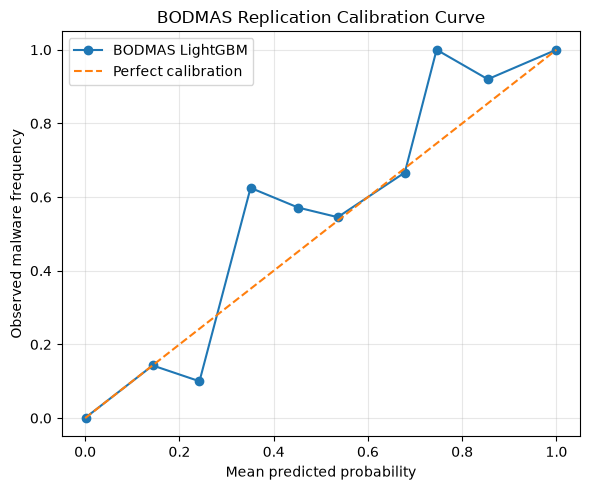


Stage 8 BODMAS Independent Replication Summary
------------------------------------------------
Scientific role: independent_replication_benchmark_not_direct_frozen_model_external_validation
Direct frozen MalTrust external validation: False
Uses EMBER revised_strict_clean_699: False
Uses torch / touches CUDA: False
LightGBM held-out training mode: gpu
CV LightGBM modes: ['gpu']
Rows: 134435
Features: 2381
Train samples: 114269
Test samples: 20166
Split protocol: GroupShuffleSplit by feature-row hash
Train/test row-hash overlap: 0
CV protocol: StratifiedGroupKFold by feature-row hash
Runtime: 9.14min
Artifact directory: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\stage8_bodmas_independent_replication_gpu_safe_v2

Held-out BODMAS LightGBM replication metrics:


,Benchmark_Role,Dataset,Feature_Space,Model,Direct_Frozen_MalTrust_External_Validation,Uses_EMBER_revised_strict_clean_699,Uses_BODMAS_Specific_Feature_Space,Split_Protocol,Train_Test_Row_Hash_Overlap,LightGBM_Training_Mode,...,Specificity_TNR,F1,MCC,ROC_AUC,PR_AUC,Brier_Score,Log_Loss,ECE,FPR,FNR
0,Independent BODMAS replication benchmark,BODMAS,BODMAS-specific numeric feature space,LightGBM same-protocol replication,False,False,True,GroupShuffleSplit by feature-row hash,0,gpu,...,0.998704,0.997205,0.995134,0.999884,0.999865,0.00195,0.008492,0.000964,0.001296,0.003839



BODMAS cross-validation summary:


,Metric,CV_Mean,CV_Std,CV_Min,CV_Max
0,Accuracy,0.997277,0.000309,0.996876,0.997731
1,Balanced_Accuracy,0.997109,0.000317,0.996683,0.997551
2,Precision,0.997640,0.000405,0.997289,0.998338
3,Recall_TPR,0.995968,0.000397,0.995374,0.996335
4,Specificity_TNR,0.998250,0.000301,0.997991,0.998769
5,F1,0.996803,0.000363,0.996331,0.997335
6,MCC,0.994434,0.000633,0.993612,0.995362
7,ROC_AUC,0.999857,0.000043,0.999830,0.999934
8,PR_AUC,0.999841,0.000042,0.999814,0.999916
9,Brier_Score,0.002222,0.000285,0.001873,0.002614



BODMAS out-of-fold metrics:


...


BODMAS McNemar paired comparison:


,Comparison,Model_A,Model_B,McNemar_Statistic,p_value,Model_A_Correct_Model_B_Wrong,Model_A_Wrong_Model_B_Correct,Significant_At_0_05
0,BODMAS LightGBM vs LogisticRegression,BODMAS LightGBM,LogisticRegression,185.003788,0.0,243,21,True



Claim boundary:


,Claim,Allowed,Evidence
0,BODMAS is an independent replication benchmark,True,The cell trains and evaluates a BODMAS-specifi...
1,BODMAS is direct frozen MalTrust-Hybrid-GCT ex...,False,No frozen EMBER-trained MalTrust model is scor...
2,BODMAS uses revised_strict_clean_699 EMBER fea...,False,The BODMAS benchmark uses its own numeric feat...
3,GPU was required for scientific validity,False,GPU is optional acceleration only; CPU fallbac...
4,Duplicate row-hash leakage was audited,True,Duplicate row-hash count=7; train/test row-has...



Saved artifacts:
Dataset report: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\stage8_bodmas_independent_replication_gpu_safe_v2\stage8_bodmas_dataset_report.json
Held-out metrics: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\stage8_bodmas_independent_replication_gpu_safe_v2\stage8_bodmas_heldout_lightgbm_metrics.csv
CV summary: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\stage8_bodmas_independent_replication_gpu_safe_v2\stage8_bodmas_cross_validation_summary.csv
Bootstrap CI: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\stage8_bodmas_independent_replication_gpu_safe_v2\stage8_bodmas_bootstrap_confidence_intervals.csv
Calibration metrics: C:\User\LENOVO\Desktop\Maltrust_xai_artifacts\external_validation\ember2024_win64_test_period\stage8_bodmas_independent_replication_gpu_safe_v2\stage8_bodma

In [58]:
# ============================================================
# MalTrust-XAI | Stage 8 v2
# Independent BODMAS Replication Benchmark + CV Platform
#
# Updated for current MalTrust-Hybrid-GCT manuscript pipeline:
# - BODMAS remains an independent replication benchmark, not direct
#   frozen-model external validation.
# - Uses BODMAS-specific feature space only.
# - Optional LightGBM GPU acceleration with safe CPU fallback.
# - Avoids torch/CUDA entirely; this cell will not poison CUDA context.
# - Performs duplicate row-hash audit and leakage-aware splitting.
# - Supports held-out test, stratified/group CV, bootstrap CIs,
#   calibration, and paired logistic baseline comparison.
# - Saves manuscript-safe claim-boundary table and package artifacts.
# ============================================================

import os
import gc
import json
import time
import glob
import shutil
import zipfile
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timezone

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GroupShuffleSplit
try:
    from sklearn.model_selection import StratifiedGroupKFold
except Exception:
    StratifiedGroupKFold = None

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    log_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2

import lightgbm as lgb
import joblib

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# User/runtime configuration
# ------------------------------------------------------------
BODMAS_ROOT = globals().get(
    "BODMAS_ROOT",
    r"C:\Users\LENOVO\Desktop\Maltrust-XAI_Framework\data\BODMAS"
)

BODMAS_RANDOM_STATE = int(globals().get("BODMAS_RANDOM_STATE", 42))
BODMAS_TEST_SIZE = float(globals().get("BODMAS_TEST_SIZE", 0.15))
BODMAS_CV_FOLDS = int(globals().get("BODMAS_CV_FOLDS", 5))
BODMAS_BOOTSTRAP_ITERATIONS = int(globals().get("BODMAS_BOOTSTRAP_ITERATIONS", 500))
BODMAS_MAX_ROWS = globals().get("BODMAS_MAX_ROWS", None)  # e.g., 100000 for debug
BODMAS_RUN_LOGISTIC_BASELINE = bool(globals().get("BODMAS_RUN_LOGISTIC_BASELINE", True))
BODMAS_CREATE_ZIP = bool(globals().get("BODMAS_CREATE_ZIP", True))

# GPU is optional for LightGBM only. This cell does not import torch.
# If the installed LightGBM was not compiled with GPU support, it falls back to CPU.
BODMAS_USE_LIGHTGBM_GPU_IF_AVAILABLE = bool(globals().get("BODMAS_USE_LIGHTGBM_GPU_IF_AVAILABLE", True))
BODMAS_LIGHTGBM_GPU_DEVICE_ID = int(globals().get("BODMAS_LIGHTGBM_GPU_DEVICE_ID", 0))
BODMAS_LIGHTGBM_GPU_PLATFORM_ID = int(globals().get("BODMAS_LIGHTGBM_GPU_PLATFORM_ID", 0))

# Conservative GPU settings for 8GB cards. Increase max_bin only if stable.
BODMAS_LIGHTGBM_N_ESTIMATORS = int(globals().get("BODMAS_LIGHTGBM_N_ESTIMATORS", 300))
BODMAS_LIGHTGBM_MAX_BIN_GPU = int(globals().get("BODMAS_LIGHTGBM_MAX_BIN_GPU", 63))
BODMAS_LIGHTGBM_MAX_BIN_CPU = int(globals().get("BODMAS_LIGHTGBM_MAX_BIN_CPU", 255))

if "EXTERNAL_VALIDATION_ARTIFACT_DIR" in globals():
    # Keep BODMAS separate from final external-validation package semantics.
    STAGE8_PARENT_DIR = os.path.dirname(EXTERNAL_VALIDATION_ARTIFACT_DIR)
else:
    STAGE8_PARENT_DIR = r"C:\Users\LENOVO\Desktop\Maltrust_xai_artifacts"

STAGE8_ARTIFACT_DIR = os.path.join(
    STAGE8_PARENT_DIR,
    "stage8_bodmas_independent_replication_gpu_safe_v2"
)
os.makedirs(STAGE8_ARTIFACT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def utc_now_string():
    return datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S %Z")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4, sort_keys=True, default=str)


def save_json_atomic(obj, path):
    tmp_path = path + ".tmp"
    save_json(obj, tmp_path)
    os.replace(tmp_path, path)


def save_csv_atomic(df, path, index=False):
    tmp_path = path + ".tmp"
    df.to_csv(tmp_path, index=index)
    os.replace(tmp_path, path)


def sha256_file_local(filepath, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds / 60:.2f}min"
    return f"{seconds / 3600:.2f}h"


def safe_log_loss(y_true, y_score):
    y_score = np.clip(np.asarray(y_score, dtype=float), 1e-15, 1.0 - 1e-15)
    return float(log_loss(y_true, y_score, labels=[0, 1]))


def compute_ece(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0.0, 1.0)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_score, bins, right=False) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    ece = 0.0
    rows = []
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())
        if count == 0:
            continue
        mean_conf = float(y_score[mask].mean())
        observed = float(y_true[mask].mean())
        gap = abs(observed - mean_conf)
        ece += (count / len(y_true)) * gap
        rows.append({
            "Bin": int(bin_id),
            "Bin_Lower": float(bins[bin_id]),
            "Bin_Upper": float(bins[bin_id + 1]),
            "Count": count,
            "Mean_Confidence": mean_conf,
            "Observed_Frequency": observed,
            "Absolute_Gap": float(gap),
        })
    return float(ece), pd.DataFrame(rows)


def mcnemar_test(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)
    correct_a = pred_a == y_true
    correct_b = pred_b == y_true
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    statistic = ((abs(b - c) - 1) ** 2) / (b + c + 1e-12)
    p_value = float(1.0 - chi2.cdf(statistic, df=1))
    return {
        "McNemar_Statistic": float(statistic),
        "p_value": p_value,
        "Model_A_Correct_Model_B_Wrong": b,
        "Model_A_Wrong_Model_B_Correct": c,
        "Significant_At_0_05": bool(p_value < 0.05),
    }


def compute_binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0.0, 1.0)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "Samples": int(len(y_true)),
        "Label_0_Count": int((y_true == 0).sum()),
        "Label_1_Count": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity_TNR": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Brier_Score": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) == 2 else np.nan,
        "Log_Loss": safe_log_loss(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        "ECE": compute_ece(y_true, y_score, n_bins=10)[0] if len(np.unique(y_true)) == 2 else np.nan,
        "FPR": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "FNR": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }


def bootstrap_ci_metric(y_true, y_score, metric_name, n_boot=500, seed=42, threshold=0.5):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = (y_score >= threshold).astype(int)
    scores = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt = y_true[idx]
        ys = y_score[idx]
        yp = y_pred[idx]
        try:
            if metric_name == "Accuracy":
                value = accuracy_score(yt, yp)
            elif metric_name == "Balanced_Accuracy":
                value = balanced_accuracy_score(yt, yp)
            elif metric_name == "F1":
                value = f1_score(yt, yp, zero_division=0)
            elif metric_name == "MCC":
                value = matthews_corrcoef(yt, yp)
            elif metric_name == "ROC_AUC":
                if len(np.unique(yt)) < 2:
                    continue
                value = roc_auc_score(yt, ys)
            elif metric_name == "PR_AUC":
                if len(np.unique(yt)) < 2:
                    continue
                value = average_precision_score(yt, ys)
            elif metric_name == "Brier_Score":
                if len(np.unique(yt)) < 2:
                    continue
                value = brier_score_loss(yt, np.clip(ys, 0, 1))
            else:
                raise ValueError(f"Unsupported metric: {metric_name}")
            scores.append(float(value))
        except Exception:
            continue
    if not scores:
        return np.nan, np.nan, np.nan, 0
    scores = np.asarray(scores)
    return float(scores.mean()), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5)), int(len(scores))

# ------------------------------------------------------------
# BODMAS loader
# ------------------------------------------------------------
def discover_bodmas_files(root_dir):
    patterns = ["**/*.npz", "**/*.csv", "**/*.parquet", "**/*.pkl", "**/*.joblib"]
    files = []
    for pattern in patterns:
        files.extend(glob.glob(os.path.join(root_dir, pattern), recursive=True))
    return sorted(files)


def normalize_binary_labels(y):
    y = np.asarray(y)
    unique = sorted(pd.Series(y).dropna().unique().tolist())
    if set(unique).issubset({0, 1}):
        return y.astype(int)
    if set(unique).issubset({-1, 1}):
        return np.where(y == 1, 1, 0).astype(int)
    if set(unique).issubset({1, 2}):
        return np.where(y == 2, 1, 0).astype(int)
    raise ValueError(f"Unsupported BODMAS label values: {unique[:20]}")


def load_bodmas_npz(path):
    obj = np.load(path, allow_pickle=True)
    keys = list(obj.keys())
    lower_keys = {k.lower(): k for k in keys}
    x_candidates = ["x", "data", "features", "feature", "x_train", "arr_0"]
    y_candidates = ["y", "label", "labels", "target", "targets", "arr_1"]
    x_key = None
    y_key = None
    for key in x_candidates:
        if key in lower_keys and getattr(obj[lower_keys[key]], "ndim", None) == 2:
            x_key = lower_keys[key]
            break
    if x_key is None:
        for key in keys:
            if getattr(obj[key], "ndim", None) == 2:
                x_key = key
                break
    for key in y_candidates:
        if key in lower_keys and getattr(obj[lower_keys[key]], "ndim", None) == 1:
            y_key = lower_keys[key]
            break
    if y_key is None and x_key is not None:
        for key in keys:
            if getattr(obj[key], "ndim", None) == 1 and len(obj[key]) == obj[x_key].shape[0]:
                y_key = key
                break
    if x_key is None or y_key is None:
        raise ValueError(f"Could not identify X/y arrays in NPZ file: {path}. Keys: {keys}")
    X = obj[x_key]
    y = normalize_binary_labels(obj[y_key])
    feature_names = [f"bodmas_f_{i:05d}" for i in range(X.shape[1])]
    X_df = pd.DataFrame(X, columns=feature_names)
    return X_df, y, {"source_path": path, "source_type": "npz", "npz_keys": keys, "x_key": x_key, "y_key": y_key}


def load_bodmas_table(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        df = pd.read_csv(path)
    elif ext == ".parquet":
        df = pd.read_parquet(path)
    elif ext in [".pkl", ".joblib"]:
        df = joblib.load(path)
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Loaded object is not a DataFrame: {path}")
    else:
        raise ValueError(f"Unsupported table file type: {path}")
    label_candidates = ["label", "y", "target", "malware", "is_malware", "class"]
    label_col = next((c for c in label_candidates if c in df.columns), None)
    if label_col is None:
        raise ValueError(f"No label column found in BODMAS table file: {path}")
    y = normalize_binary_labels(df[label_col].to_numpy())
    id_cols = ["sha256", "sha1", "md5", "filename", "file_name", "path", "sample_id"]
    X_df = df.drop(columns=[label_col] + [c for c in id_cols if c in df.columns], errors="ignore")
    X_df = X_df.select_dtypes(include=[np.number]).copy()
    X_df.columns = [str(c) for c in X_df.columns]
    return X_df, y, {
        "source_path": path,
        "source_type": ext.replace(".", ""),
        "label_column": label_col,
        "original_column_count": int(df.shape[1]),
        "numeric_feature_count": int(X_df.shape[1]),
    }


def load_bodmas_dataset(root_dir):
    if not os.path.exists(root_dir):
        raise FileNotFoundError(f"BODMAS_ROOT not found: {root_dir}")
    files = discover_bodmas_files(root_dir)
    if not files:
        raise FileNotFoundError(f"No BODMAS files found under: {root_dir}")
    print("Discovered BODMAS files:", len(files))
    for f in files[:10]:
        print("-", f)
    load_reports = []
    npz_files = [f for f in files if f.lower().endswith(".npz")]
    if npz_files:
        X_df, y, report = load_bodmas_npz(npz_files[0])
        load_reports.append(report)
    else:
        X_parts, y_parts = [], []
        for path in [f for f in files if f.lower().endswith((".csv", ".parquet", ".pkl", ".joblib"))]:
            try:
                X_part, y_part, report = load_bodmas_table(path)
                X_parts.append(X_part)
                y_parts.append(y_part)
                load_reports.append(report)
            except Exception as e:
                load_reports.append({"source_path": path, "load_status": "failed", "error": str(e)})
        if not X_parts:
            raise RuntimeError("No BODMAS table files could be loaded.")
        common_features = sorted(list(set.intersection(*[set(x.columns) for x in X_parts])))
        if not common_features:
            raise ValueError("No common numeric feature columns across BODMAS table files.")
        X_df = pd.concat([x[common_features] for x in X_parts], ignore_index=True)
        y = np.concatenate(y_parts).astype(int)
    X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    y = normalize_binary_labels(y)
    if len(X_df) != len(y):
        raise ValueError(f"X/y row mismatch: X={len(X_df)}, y={len(y)}")
    if BODMAS_MAX_ROWS is not None and len(X_df) > int(BODMAS_MAX_ROWS):
        rng = np.random.default_rng(BODMAS_RANDOM_STATE)
        idx = rng.choice(len(X_df), size=int(BODMAS_MAX_ROWS), replace=False)
        X_df = X_df.iloc[idx].reset_index(drop=True)
        y = y[idx]
    row_hash = pd.util.hash_pandas_object(X_df, index=False).astype(str).to_numpy()
    unique_row_hash_count = int(pd.Series(row_hash).nunique())
    duplicate_row_count = int(len(row_hash) - unique_row_hash_count)
    report = {
        "bodmas_root": root_dir,
        "loaded_rows": int(len(X_df)),
        "feature_count": int(X_df.shape[1]),
        "label_0_count": int((y == 0).sum()),
        "label_1_count": int((y == 1).sum()),
        "row_hash_unique_count": unique_row_hash_count,
        "row_hash_duplicate_count": duplicate_row_count,
        "row_hash_duplicate_rate": float(duplicate_row_count / len(X_df)),
        "load_reports": load_reports,
    }
    return X_df, y, row_hash, report

# ------------------------------------------------------------
# LightGBM model factory and GPU-safe fitting
# ------------------------------------------------------------
def make_lgbm_params(mode="cpu", random_state=42):
    params = dict(
        n_estimators=BODMAS_LIGHTGBM_N_ESTIMATORS,
        learning_rate=0.05,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        n_jobs=-1,
        random_state=int(random_state),
        force_col_wise=True,
        verbosity=-1,
    )
    if mode == "gpu":
        params.update(dict(
            device_type="gpu",
            gpu_platform_id=BODMAS_LIGHTGBM_GPU_PLATFORM_ID,
            gpu_device_id=BODMAS_LIGHTGBM_GPU_DEVICE_ID,
            max_bin=BODMAS_LIGHTGBM_MAX_BIN_GPU,
        ))
    else:
        params.update(dict(max_bin=BODMAS_LIGHTGBM_MAX_BIN_CPU))
    return params


def fit_lightgbm_with_optional_gpu(X_train, y_train, random_state=42, label="LightGBM"):
    attempts = []
    if BODMAS_USE_LIGHTGBM_GPU_IF_AVAILABLE:
        attempts.append("gpu")
    attempts.append("cpu")
    last_error = None
    for mode in attempts:
        model = lgb.LGBMClassifier(**make_lgbm_params(mode=mode, random_state=random_state))
        try:
            print(f"Training {label} with LightGBM mode: {mode}")
            model.fit(X_train, y_train)
            return model, mode, None
        except Exception as e:
            last_error = f"{type(e).__name__}: {e}"
            print(f"{label} LightGBM {mode} failed; falling back if possible. Error: {last_error}")
            gc.collect()
    raise RuntimeError(f"All LightGBM training modes failed. Last error: {last_error}")

# ------------------------------------------------------------
# Load BODMAS
# ------------------------------------------------------------
stage8_start_time = time.time()
print("\nLoading BODMAS dataset...")
X_bodmas_df, y_bodmas, bodmas_row_hash, bodmas_dataset_report = load_bodmas_dataset(BODMAS_ROOT)
print("\nBODMAS loaded")
print("Rows:", X_bodmas_df.shape[0])
print("Features:", X_bodmas_df.shape[1])
print("Label distribution:")
print(pd.Series(y_bodmas).value_counts().sort_index())
print("Duplicate row-hash count:", bodmas_dataset_report["row_hash_duplicate_count"])

# ------------------------------------------------------------
# Leakage-aware held-out split
# ------------------------------------------------------------
use_group_split = bodmas_dataset_report["row_hash_duplicate_count"] > 0
if use_group_split:
    splitter = GroupShuffleSplit(n_splits=1, test_size=BODMAS_TEST_SIZE, random_state=BODMAS_RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X_bodmas_df, y_bodmas, groups=bodmas_row_hash))
    split_protocol = "GroupShuffleSplit by feature-row hash"
    X_train_b = X_bodmas_df.iloc[train_idx]
    X_test_b = X_bodmas_df.iloc[test_idx]
    y_train_b = y_bodmas[train_idx]
    y_test_b = y_bodmas[test_idx]
    hash_train_b = bodmas_row_hash[train_idx]
    hash_test_b = bodmas_row_hash[test_idx]
else:
    X_train_b, X_test_b, y_train_b, y_test_b, hash_train_b, hash_test_b = train_test_split(
        X_bodmas_df,
        y_bodmas,
        bodmas_row_hash,
        test_size=BODMAS_TEST_SIZE,
        stratify=y_bodmas,
        random_state=BODMAS_RANDOM_STATE,
    )
    split_protocol = "Stratified train/test split; no duplicate feature-row hashes detected"

hash_overlap_count = int(len(set(hash_train_b).intersection(set(hash_test_b))))
if hash_overlap_count > 0:
    raise AssertionError(f"Train/test row-hash overlap detected: {hash_overlap_count}")

print("\nBODMAS split protocol:", split_protocol)
print("BODMAS train:", X_train_b.shape)
print("BODMAS test:", X_test_b.shape)
print("Train labels:")
print(pd.Series(y_train_b).value_counts().sort_index())
print("Test labels:")
print(pd.Series(y_test_b).value_counts().sort_index())

# ------------------------------------------------------------
# Held-out BODMAS LightGBM evaluation
# ------------------------------------------------------------
print("\nTraining BODMAS LightGBM replication model...")
bodmas_lgbm_model, bodmas_lgbm_training_mode, bodmas_lgbm_gpu_error = fit_lightgbm_with_optional_gpu(
    X_train_b,
    y_train_b,
    random_state=BODMAS_RANDOM_STATE,
    label="BODMAS held-out LightGBM",
)

bodmas_lgbm_score = np.clip(bodmas_lgbm_model.predict_proba(X_test_b)[:, 1], 0.0, 1.0)
bodmas_lgbm_pred = (bodmas_lgbm_score >= 0.5).astype(int)
bodmas_lgbm_metrics = compute_binary_metrics(y_test_b, bodmas_lgbm_score, threshold=0.5)

bodmas_lgbm_results = pd.DataFrame([{
    "Benchmark_Role": "Independent BODMAS replication benchmark",
    "Dataset": "BODMAS",
    "Feature_Space": "BODMAS-specific numeric feature space",
    "Model": "LightGBM same-protocol replication",
    "Direct_Frozen_MalTrust_External_Validation": False,
    "Uses_EMBER_revised_strict_clean_699": False,
    "Uses_BODMAS_Specific_Feature_Space": True,
    "Split_Protocol": split_protocol,
    "Train_Test_Row_Hash_Overlap": hash_overlap_count,
    "LightGBM_Training_Mode": bodmas_lgbm_training_mode,
    "Train_Samples": int(len(y_train_b)),
    "Test_Samples": int(len(y_test_b)),
    "Features": int(X_train_b.shape[1]),
    **bodmas_lgbm_metrics,
}])

# ------------------------------------------------------------
# Optional paired logistic baseline
# ------------------------------------------------------------
baseline_result_rows = []
mcnemar_rows = []
if BODMAS_RUN_LOGISTIC_BASELINE:
    baseline_name = "LogisticRegression"
    baseline_model = make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(max_iter=1000, solver="saga", n_jobs=-1, random_state=BODMAS_RANDOM_STATE),
    )
    print(f"\nTraining BODMAS paired baseline: {baseline_name}")
    try:
        baseline_model.fit(X_train_b, y_train_b)
        baseline_score = np.clip(baseline_model.predict_proba(X_test_b)[:, 1], 0.0, 1.0)
        baseline_pred = (baseline_score >= 0.5).astype(int)
        baseline_metrics = compute_binary_metrics(y_test_b, baseline_score, threshold=0.5)
        baseline_result_rows.append({
            "Benchmark_Role": "Independent BODMAS paired baseline",
            "Dataset": "BODMAS",
            "Feature_Space": "BODMAS-specific numeric feature space",
            "Model": baseline_name,
            "Train_Samples": int(len(y_train_b)),
            "Test_Samples": int(len(y_test_b)),
            "Features": int(X_train_b.shape[1]),
            **baseline_metrics,
        })
        mcnemar_rows.append({
            "Comparison": f"BODMAS LightGBM vs {baseline_name}",
            "Model_A": "BODMAS LightGBM",
            "Model_B": baseline_name,
            **mcnemar_test(y_test_b, bodmas_lgbm_pred, baseline_pred),
        })
    except Exception as e:
        baseline_result_rows.append({
            "Benchmark_Role": "Independent BODMAS paired baseline",
            "Dataset": "BODMAS",
            "Model": baseline_name,
            "Status": "FAILED",
            "Error": f"{type(e).__name__}: {e}",
        })

bodmas_baseline_results = pd.DataFrame(baseline_result_rows)
bodmas_mcnemar_results = pd.DataFrame(mcnemar_rows)

# ------------------------------------------------------------
# Stratified/group cross-validation
# ------------------------------------------------------------
print(f"\nRunning BODMAS {BODMAS_CV_FOLDS}-fold cross-validation...")
if use_group_split and StratifiedGroupKFold is not None:
    cv_splits = list(StratifiedGroupKFold(n_splits=BODMAS_CV_FOLDS, shuffle=True, random_state=BODMAS_RANDOM_STATE).split(
        X_bodmas_df, y_bodmas, groups=bodmas_row_hash
    ))
    cv_protocol = "StratifiedGroupKFold by feature-row hash"
elif use_group_split:
    cv_splits = list(StratifiedKFold(n_splits=BODMAS_CV_FOLDS, shuffle=True, random_state=BODMAS_RANDOM_STATE).split(X_bodmas_df, y_bodmas))
    cv_protocol = "StratifiedKFold fallback; duplicate row hashes exist, use CV cautiously"
else:
    cv_splits = list(StratifiedKFold(n_splits=BODMAS_CV_FOLDS, shuffle=True, random_state=BODMAS_RANDOM_STATE).split(X_bodmas_df, y_bodmas))
    cv_protocol = "StratifiedKFold; no duplicate feature-row hashes detected"

cv_rows = []
oof_scores = np.zeros(len(X_bodmas_df), dtype=np.float64)
oof_preds = np.zeros(len(X_bodmas_df), dtype=np.int8)
fold_modes = []
iterator = cv_splits
if tqdm is not None:
    iterator = tqdm(cv_splits, total=BODMAS_CV_FOLDS, desc="BODMAS CV folds", unit="fold")

for fold_id, (train_idx, val_idx) in enumerate(iterator, start=1):
    X_tr = X_bodmas_df.iloc[train_idx]
    X_va = X_bodmas_df.iloc[val_idx]
    y_tr = y_bodmas[train_idx]
    y_va = y_bodmas[val_idx]
    fold_model, fold_mode, _ = fit_lightgbm_with_optional_gpu(
        X_tr,
        y_tr,
        random_state=BODMAS_RANDOM_STATE + fold_id,
        label=f"BODMAS CV fold {fold_id}",
    )
    fold_modes.append(fold_mode)
    y_score_fold = np.clip(fold_model.predict_proba(X_va)[:, 1], 0.0, 1.0)
    y_pred_fold = (y_score_fold >= 0.5).astype(int)
    oof_scores[val_idx] = y_score_fold
    oof_preds[val_idx] = y_pred_fold
    fold_metrics = compute_binary_metrics(y_va, y_score_fold, threshold=0.5)
    cv_rows.append({
        "Fold": int(fold_id),
        "CV_Protocol": cv_protocol,
        "LightGBM_Training_Mode": fold_mode,
        "Train_Samples": int(len(train_idx)),
        "Validation_Samples": int(len(val_idx)),
        **fold_metrics,
    })
    del fold_model, X_tr, X_va, y_tr, y_va
    gc.collect()

bodmas_cv_results = pd.DataFrame(cv_rows)
bodmas_cv_summary = pd.DataFrame([
    {
        "Metric": metric,
        "CV_Mean": float(bodmas_cv_results[metric].astype(float).mean()),
        "CV_Std": float(bodmas_cv_results[metric].astype(float).std(ddof=1)),
        "CV_Min": float(bodmas_cv_results[metric].astype(float).min()),
        "CV_Max": float(bodmas_cv_results[metric].astype(float).max()),
    }
    for metric in ["Accuracy", "Balanced_Accuracy", "Precision", "Recall_TPR", "Specificity_TNR", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score", "ECE"]
])

bodmas_oof_metrics = pd.DataFrame([{
    "Evaluation": "BODMAS LightGBM out-of-fold predictions",
    "CV_Protocol": cv_protocol,
    "Samples": int(len(y_bodmas)),
    "Features": int(X_bodmas_df.shape[1]),
    **compute_binary_metrics(y_bodmas, oof_scores, threshold=0.5),
}])

# ------------------------------------------------------------
# Bootstrap CIs on held-out test predictions
# ------------------------------------------------------------
ci_rows = []
for metric_name in ["Accuracy", "Balanced_Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier_Score"]:
    mean_val, low_val, high_val, valid_boots = bootstrap_ci_metric(
        y_true=y_test_b,
        y_score=bodmas_lgbm_score,
        metric_name=metric_name,
        n_boot=BODMAS_BOOTSTRAP_ITERATIONS,
        seed=BODMAS_RANDOM_STATE,
        threshold=0.5,
    )
    ci_rows.append({
        "Metric": metric_name,
        "Bootstrap_Mean": mean_val,
        "CI_95_Lower": low_val,
        "CI_95_Upper": high_val,
        "Valid_Bootstrap_Iterations": valid_boots,
        "Requested_Bootstrap_Iterations": BODMAS_BOOTSTRAP_ITERATIONS,
    })
bodmas_ci_results = pd.DataFrame(ci_rows)

# ------------------------------------------------------------
# Calibration
# ------------------------------------------------------------
prob_true, prob_pred = calibration_curve(y_test_b, bodmas_lgbm_score, n_bins=10, strategy="uniform")
bodmas_calibration_table = pd.DataFrame({
    "Mean_Predicted_Probability": prob_pred,
    "Observed_Positive_Frequency": prob_true,
})
heldout_ece, bodmas_calibration_bins = compute_ece(y_test_b, bodmas_lgbm_score, n_bins=10)
bodmas_calibration_metrics = pd.DataFrame([{
    "Dataset": "BODMAS",
    "Model": "LightGBM same-protocol replication",
    "Samples": int(len(y_test_b)),
    "Brier_Score": float(brier_score_loss(y_test_b, bodmas_lgbm_score)),
    "Log_Loss": safe_log_loss(y_test_b, bodmas_lgbm_score),
    "Expected_Calibration_Error": float(heldout_ece),
}])

calibration_plot_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_calibration_curve.png")
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="BODMAS LightGBM")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed malware frequency")
plt.title("BODMAS Replication Calibration Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(calibration_plot_path, dpi=300)
plt.show()

# ------------------------------------------------------------
# Claim boundary
# ------------------------------------------------------------
claim_boundary_df = pd.DataFrame([
    {
        "Claim": "BODMAS is an independent replication benchmark",
        "Allowed": True,
        "Evidence": "The cell trains and evaluates a BODMAS-specific LightGBM replication model on BODMAS-specific features.",
    },
    {
        "Claim": "BODMAS is direct frozen MalTrust-Hybrid-GCT external validation",
        "Allowed": False,
        "Evidence": "No frozen EMBER-trained MalTrust model is scored directly on BODMAS; this is a replication benchmark.",
    },
    {
        "Claim": "BODMAS uses revised_strict_clean_699 EMBER feature space",
        "Allowed": False,
        "Evidence": "The BODMAS benchmark uses its own numeric feature space.",
    },
    {
        "Claim": "GPU was required for scientific validity",
        "Allowed": False,
        "Evidence": "GPU is optional acceleration only; CPU fallback preserves the same benchmark protocol.",
    },
    {
        "Claim": "Duplicate row-hash leakage was audited",
        "Allowed": True,
        "Evidence": f"Duplicate row-hash count={bodmas_dataset_report['row_hash_duplicate_count']}; train/test row-hash overlap={hash_overlap_count}.",
    },
])

# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
dataset_report_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_dataset_report.json")
heldout_metrics_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_heldout_lightgbm_metrics.csv")
baseline_metrics_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_paired_baseline_metrics.csv")
cv_results_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_cross_validation_folds.csv")
cv_summary_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_cross_validation_summary.csv")
oof_metrics_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_oof_metrics.csv")
ci_results_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_bootstrap_confidence_intervals.csv")
calibration_table_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_calibration_table.csv")
calibration_bins_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_calibration_bins.csv")
calibration_metrics_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_calibration_metrics.csv")
mcnemar_results_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_mcnemar_results.csv")
claim_boundary_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_claim_boundary.csv")
model_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_lightgbm_replication_model.joblib")
summary_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_independent_replication_summary.json")
artifact_index_path = os.path.join(STAGE8_ARTIFACT_DIR, "stage8_bodmas_artifact_index.csv")

save_json_atomic(bodmas_dataset_report, dataset_report_path)
save_csv_atomic(bodmas_lgbm_results, heldout_metrics_path, index=False)
save_csv_atomic(bodmas_baseline_results, baseline_metrics_path, index=False)
save_csv_atomic(bodmas_cv_results, cv_results_path, index=False)
save_csv_atomic(bodmas_cv_summary, cv_summary_path, index=False)
save_csv_atomic(bodmas_oof_metrics, oof_metrics_path, index=False)
save_csv_atomic(bodmas_ci_results, ci_results_path, index=False)
save_csv_atomic(bodmas_calibration_table, calibration_table_path, index=False)
save_csv_atomic(bodmas_calibration_bins, calibration_bins_path, index=False)
save_csv_atomic(bodmas_calibration_metrics, calibration_metrics_path, index=False)
save_csv_atomic(bodmas_mcnemar_results, mcnemar_results_path, index=False)
save_csv_atomic(claim_boundary_df, claim_boundary_path, index=False)
joblib.dump(bodmas_lgbm_model, model_path)

stage8_runtime = time.time() - stage8_start_time
stage8_summary = {
    "cell": "Stage 8 v2",
    "purpose": "Independent BODMAS replication benchmark and cross-validation platform",
    "scientific_role": "independent_replication_benchmark_not_direct_frozen_model_external_validation",
    "direct_frozen_maltrust_external_validation": False,
    "uses_ember_revised_strict_clean_699": False,
    "uses_bodmas_specific_feature_space": True,
    "uses_torch": False,
    "touches_cuda": False,
    "gpu_optional_acceleration_only": True,
    "bodmas_root": BODMAS_ROOT,
    "rows": int(X_bodmas_df.shape[0]),
    "features": int(X_bodmas_df.shape[1]),
    "train_samples": int(len(y_train_b)),
    "test_samples": int(len(y_test_b)),
    "split_protocol": split_protocol,
    "train_test_row_hash_overlap": int(hash_overlap_count),
    "cv_protocol": cv_protocol,
    "cv_folds": int(BODMAS_CV_FOLDS),
    "bootstrap_iterations": int(BODMAS_BOOTSTRAP_ITERATIONS),
    "heldout_lightgbm_training_mode": bodmas_lgbm_training_mode,
    "cv_lightgbm_training_modes": sorted(list(set(fold_modes))),
    "heldout_metrics_path": heldout_metrics_path,
    "cv_summary_path": cv_summary_path,
    "oof_metrics_path": oof_metrics_path,
    "ci_results_path": ci_results_path,
    "calibration_metrics_path": calibration_metrics_path,
    "mcnemar_results_path": mcnemar_results_path,
    "claim_boundary_path": claim_boundary_path,
    "model_path": model_path,
    "runtime_seconds": float(stage8_runtime),
    "runtime_formatted": format_seconds(stage8_runtime),
    "created_at_local": now_str(),
    "created_at_utc": utc_now_string(),
}
save_json_atomic(stage8_summary, summary_path)

# Artifact index
artifact_rows = []
for root, _, files in os.walk(STAGE8_ARTIFACT_DIR):
    for file_name in files:
        path = os.path.join(root, file_name)
        if file_name.endswith(".tmp"):
            continue
        artifact_rows.append({
            "File_Name": file_name,
            "File_Path": path,
            "Relative_Path": os.path.relpath(path, STAGE8_ARTIFACT_DIR),
            "File_Size_Bytes": int(os.path.getsize(path)),
            "SHA256": sha256_file_local(path),
        })
artifact_index_df = pd.DataFrame(artifact_rows)
save_csv_atomic(artifact_index_df, artifact_index_path, index=False)

# Optional ZIP
zip_file = None
zip_sha256 = None
if BODMAS_CREATE_ZIP:
    zip_base = os.path.join(os.path.dirname(STAGE8_ARTIFACT_DIR), "stage8_bodmas_independent_replication_gpu_safe_v2_package")
    zip_file = shutil.make_archive(base_name=zip_base, format="zip", root_dir=STAGE8_ARTIFACT_DIR)
    zip_sha256 = sha256_file_local(zip_file)
    with zipfile.ZipFile(zip_file, "r") as zf:
        bad_file = zf.testzip()
    if bad_file is not None:
        raise RuntimeError(f"ZIP validation failed at: {bad_file}")

try:
    EXPERIMENT_CONFIG["stage8_bodmas_summary_path"] = summary_path
    EXPERIMENT_CONFIG["stage8_bodmas_heldout_metrics_path"] = heldout_metrics_path
    EXPERIMENT_CONFIG["stage8_bodmas_cv_summary_path"] = cv_summary_path
    EXPERIMENT_CONFIG["stage8_bodmas_ci_results_path"] = ci_results_path
    EXPERIMENT_CONFIG["stage8_bodmas_calibration_metrics_path"] = calibration_metrics_path
    EXPERIMENT_CONFIG["stage8_bodmas_artifact_index_path"] = artifact_index_path
    EXPERIMENT_CONFIG["stage8_bodmas_zip_file"] = zip_file
    EXPERIMENT_CONFIG["stage8_bodmas_zip_sha256"] = zip_sha256
except Exception:
    pass

# ------------------------------------------------------------
# Display and assertions
# ------------------------------------------------------------
print("\nStage 8 BODMAS Independent Replication Summary")
print("------------------------------------------------")
print("Scientific role:", stage8_summary["scientific_role"])
print("Direct frozen MalTrust external validation:", False)
print("Uses EMBER revised_strict_clean_699:", False)
print("Uses torch / touches CUDA:", False)
print("LightGBM held-out training mode:", bodmas_lgbm_training_mode)
print("CV LightGBM modes:", sorted(list(set(fold_modes))))
print("Rows:", X_bodmas_df.shape[0])
print("Features:", X_bodmas_df.shape[1])
print("Train samples:", len(y_train_b))
print("Test samples:", len(y_test_b))
print("Split protocol:", split_protocol)
print("Train/test row-hash overlap:", hash_overlap_count)
print("CV protocol:", cv_protocol)
print("Runtime:", format_seconds(stage8_runtime))
print("Artifact directory:", STAGE8_ARTIFACT_DIR)

print("\nHeld-out BODMAS LightGBM replication metrics:")
display(bodmas_lgbm_results)

print("\nBODMAS cross-validation summary:")
display(bodmas_cv_summary)

print("\nBODMAS out-of-fold metrics:")
display(bodmas_oof_metrics)

print("\nBODMAS bootstrap confidence intervals:")
display(bodmas_ci_results)

print("\nBODMAS calibration metrics:")
display(bodmas_calibration_metrics)

if len(bodmas_baseline_results) > 0:
    print("\nBODMAS paired baseline metrics:")
    display(bodmas_baseline_results)

if len(bodmas_mcnemar_results) > 0:
    print("\nBODMAS McNemar paired comparison:")
    display(bodmas_mcnemar_results)

print("\nClaim boundary:")
display(claim_boundary_df)

print("\nSaved artifacts:")
print("Dataset report:", dataset_report_path)
print("Held-out metrics:", heldout_metrics_path)
print("CV summary:", cv_summary_path)
print("Bootstrap CI:", ci_results_path)
print("Calibration metrics:", calibration_metrics_path)
print("Claim boundary:", claim_boundary_path)
print("Summary:", summary_path)
print("Artifact index:", artifact_index_path)
print("ZIP:", zip_file)
print("ZIP SHA-256:", zip_sha256)

assert len(X_bodmas_df) > 0, "BODMAS dataset is empty."
assert X_bodmas_df.shape[1] > 0, "No BODMAS numeric features found."
assert set(np.unique(y_bodmas)).issubset({0, 1}), "BODMAS labels are not binary."
assert hash_overlap_count == 0, "Train/test feature-row hash overlap detected."
assert stage8_summary["direct_frozen_maltrust_external_validation"] is False, "Do not label BODMAS as direct external validation."
assert stage8_summary["uses_ember_revised_strict_clean_699"] is False, "BODMAS must not be mislabeled as EMBER 699-space validation."
assert stage8_summary["touches_cuda"] is False, "Stage 8 must not touch torch/CUDA."

print("\nStage 8 completed successfully.")
